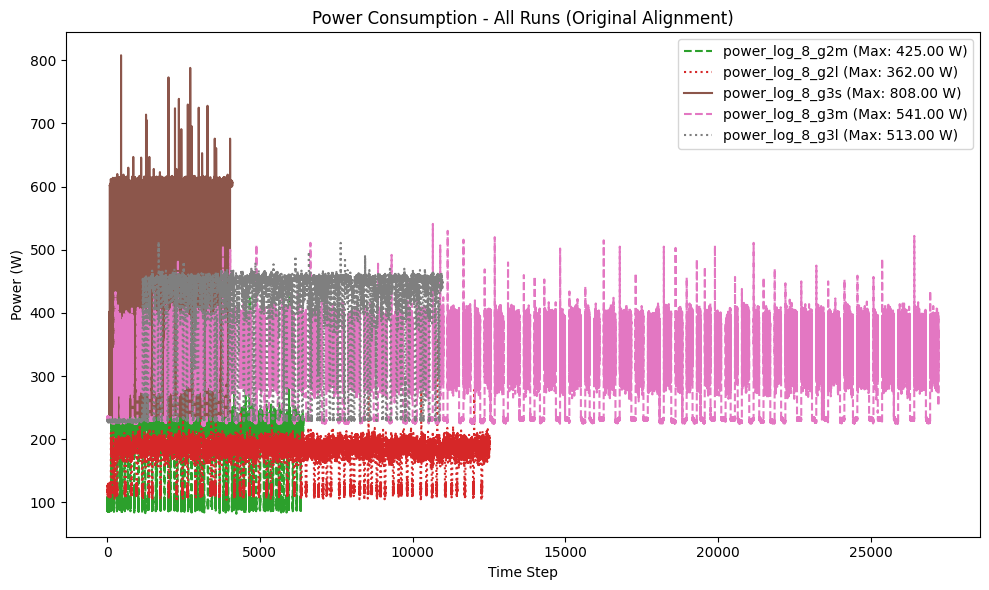

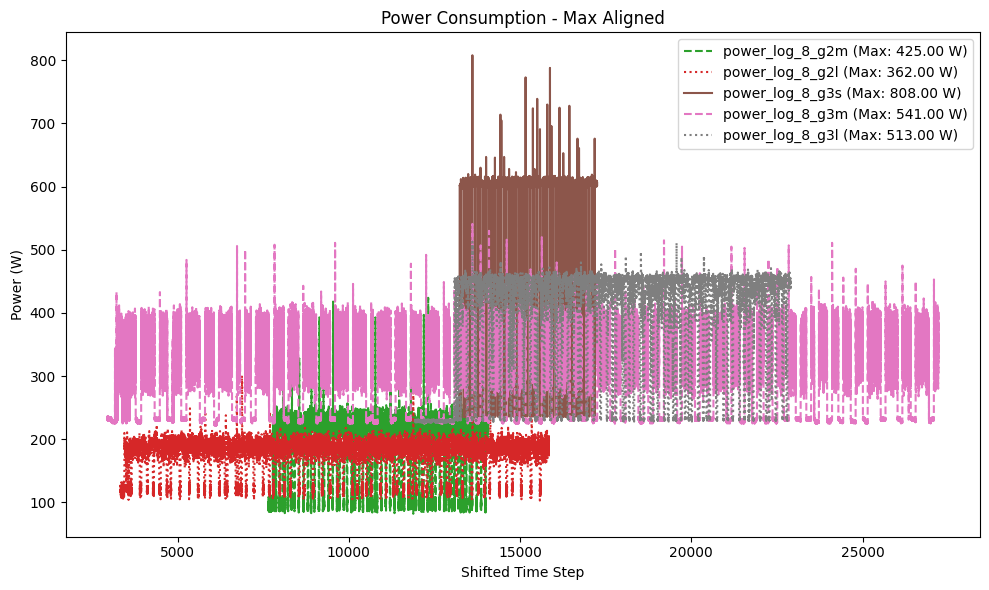

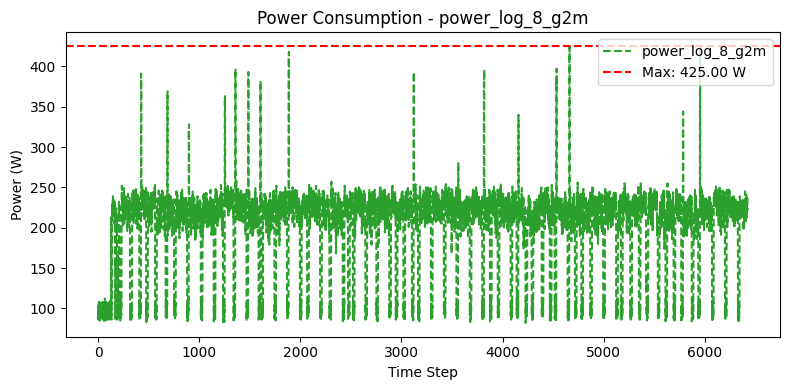

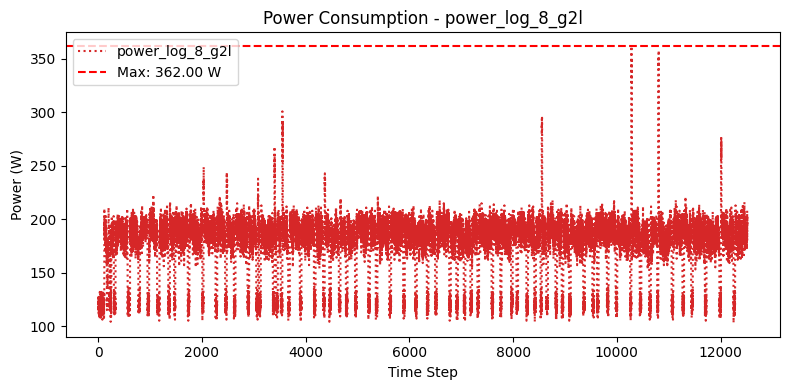

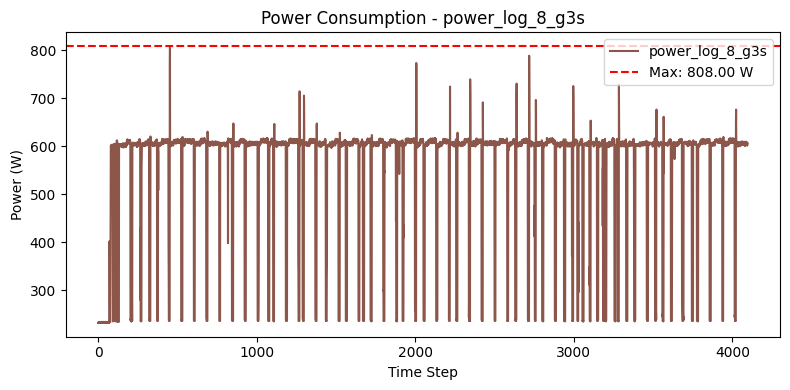

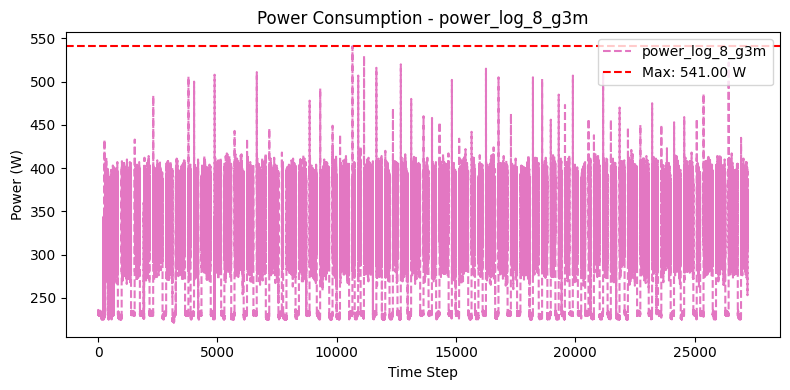

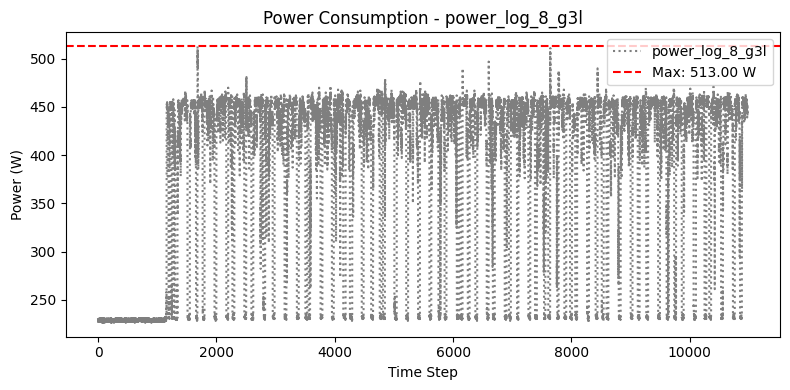


=== Max Power Consumption ===
power_log_8_g2m: 425.00 W
power_log_8_g2l: 362.00 W
power_log_8_g3s: 808.00 W
power_log_8_g3m: 541.00 W
power_log_8_g3l: 513.00 W


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
import numpy as np

# ===== SETTINGS =====
DATA_DIR = "./power_logs"  # Change to your folder path

# Distinct colors for each config
color_map = {
    "2": "#1f77b4",    # blue
    "2s": "#ff7f0e",   # orange
    "2m": "#2ca02c",   # green
    "2l": "#d62728",   # red
    "3": "#9467bd",    # purple
    "3s": "#8c564b",   # brown
    "3m": "#e377c2",   # pink
    "3l": "#7f7f7f",   # gray
}

# Line styles
style_map = {"": "-.", "s": "-", "m": "--", "l": ":"}

# Order for plotting
plot_order = ["2", "2s", "2m", "2l", "3", "3s", "3m", "3l"]

# ===== LOAD DATA =====
csv_files = glob.glob(os.path.join(DATA_DIR, "*.csv"))
data_dict = {}
max_values = {}
meta_info = {}

for file in csv_files:
    df = pd.read_csv(file)

    # Find power column
    power_col = None
    for col in df.columns:
        if "power" in col.lower():
            power_col = col
            break
    if power_col is None:
        print(f"⚠️ No power column found in {file}, skipping...")
        continue

    run_name = os.path.splitext(os.path.basename(file))[0]  # e.g., power_logs_g2s

    # Parse version & config
    parts = run_name.split("_")
    if len(parts) >= 2:
        version_config = parts[-1]  # e.g., 'g2', 'g2s', 'g3m'
        if version_config.startswith("g"):
            norm_cfg = version_config[1:]  # strip 'g' → '2', '2s', '3m', etc.
        else:
            norm_cfg = version_config
        gaudi_version = norm_cfg[0]  # '2' or '3'
        cfg_suffix = norm_cfg[1:]    # '', 's', 'm', 'l'
        meta_info[run_name] = (gaudi_version, cfg_suffix, norm_cfg)
    else:
        meta_info[run_name] = ("?", "?", "?")
        norm_cfg = "?"

    # Clean values
    power_values = (
        df[power_col]
        .astype(str)
        .str.strip()
        .str.replace("W", "", regex=False)
        .str.replace("w", "", regex=False)
        .astype(float)
        .dropna()
        .to_numpy()
    )

    data_dict[run_name] = power_values
    max_values[run_name] = np.max(power_values)

# ===== ALIGN FOR MAX =====
max_aligned_data = {}
max_length = max(len(v) for v in data_dict.values())

for run, values in data_dict.items():
    max_idx = np.argmax(values)
    shift = (max_length // 2) - max_idx
    aligned = np.full(max_length, np.nan)
    start = max(0, shift)
    end = min(max_length, shift + len(values))
    aligned[start:end] = values[:end - start]
    max_aligned_data[run] = aligned

# ===== SORT =====
sorted_runs = sorted(
    data_dict.keys(),
    key=lambda x: plot_order.index(meta_info[x][2]) if meta_info[x][2] in plot_order else 999
)

# ===== PLOT: ORIGINAL =====
plt.figure(figsize=(10, 6))
for run in sorted_runs:
    cfg_key = meta_info[run][2]  # normalized config like '2', '2s', etc.
    plt.plot(
        data_dict[run],
        label=f"{run} (Max: {max_values[run]:.2f} W)",
        color=color_map.get(cfg_key, "black"),
        linestyle=style_map.get(meta_info[run][1], "-")
    )
plt.title("Power Consumption - All Runs (Original Alignment)")
plt.xlabel("Time Step")
plt.ylabel("Power (W)")
plt.legend()
plt.tight_layout()
plt.show()

# ===== PLOT: MAX ALIGNED =====
plt.figure(figsize=(10, 6))
for run in sorted_runs:
    cfg_key = meta_info[run][2]
    plt.plot(
        max_aligned_data[run],
        label=f"{run} (Max: {max_values[run]:.2f} W)",
        color=color_map.get(cfg_key, "black"),
        linestyle=style_map.get(meta_info[run][1], "-")
    )
plt.title("Power Consumption - Max Aligned")
plt.xlabel("Shifted Time Step")
plt.ylabel("Power (W)")
plt.legend()
plt.tight_layout()
plt.show()

# ===== INDIVIDUAL PLOTS =====
for run in sorted_runs:
    cfg_key = meta_info[run][2]
    plt.figure(figsize=(8, 4))
    plt.plot(
        data_dict[run],
        color=color_map.get(cfg_key, "black"),
        linestyle=style_map.get(meta_info[run][1], "-"),
        label=run
    )
    plt.axhline(max_values[run], color='red', linestyle='--',
                label=f"Max: {max_values[run]:.2f} W")
    plt.title(f"Power Consumption - {run}")
    plt.xlabel("Time Step")
    plt.ylabel("Power (W)")
    plt.legend()
    plt.tight_layout()
    plt.show()

# ===== PRINT MAX VALUES =====
print("\n=== Max Power Consumption ===")
for run in sorted_runs:
    print(f"{run}: {max_values[run]:.2f} W")



=== Max Power Consumption ===
power_log_8_g2m: 425.00 W
power_log_8_g2l: 362.00 W
power_log_8_g3s: 808.00 W
power_log_8_g3m: 541.00 W
power_log_8_g3l: 513.00 W


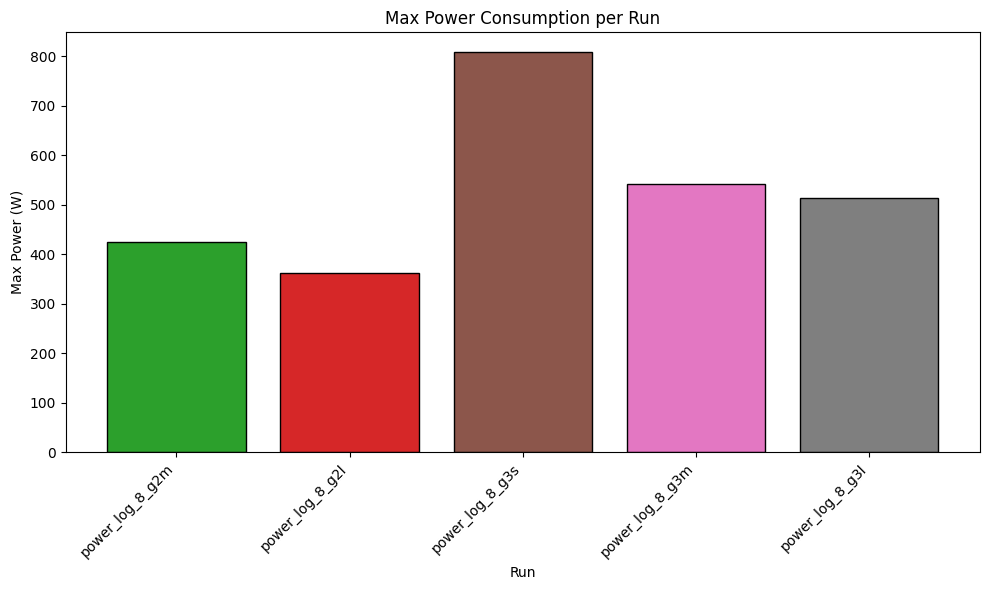

In [ ]:
# ===== PRINT MAX VALUES =====
print("\n=== Max Power Consumption ===")
for run in sorted_runs:
    print(f"{run}: {max_values[run]:.2f} W")

# ===== HISTOGRAM OF MAX VALUES =====
plt.figure(figsize=(10, 6))
bars = []
labels = []
colors = []

for run in sorted_runs:
    cfg_key = meta_info[run][2]  # normalized config
    bars.append(max_values[run])
    labels.append(run)
    colors.append(color_map.get(cfg_key, "black"))

plt.bar(labels, bars, color=colors, edgecolor="black")
plt.title("Max Power Consumption per Run")
plt.xlabel("Run")
plt.ylabel("Max Power (W)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [ ]:
g2='''
Calling add_step_closure function does not have any effect. It's lazy mode only functionality. (warning logged once)
Calling mark_step function does not have any effect. It's lazy mode only functionality. (warning logged once)
Calling iter_mark_step function does not have any effect. It's lazy mode only functionality. (warning logged once)
INFO 10-22 19:42:01 [__init__.py:254] Automatically detected platform hpu.
INFO 10-22 19:42:06 [config.py:1975] Disabled the custom all-reduce kernel because it is not supported on current platform.
INFO 10-22 19:42:07 [config.py:1975] Disabled the custom all-reduce kernel because it is not supported on current platform.
INFO 10-22 19:42:07 [config.py:1975] Disabled the custom all-reduce kernel because it is not supported on current platform.
INFO 10-22 19:42:08 [config.py:1975] Disabled the custom all-reduce kernel because it is not supported on current platform.
INFO 10-22 19:42:08 [api_server.py:1289] vLLM API server version 0.6.3.dev5453+ge9c83fca1
INFO 10-22 19:42:09 [config.py:1975] Disabled the custom all-reduce kernel because it is not supported on current platform.
INFO 10-22 19:42:09 [cli_args.py:309] non-default args: {'model': '/mnt/weka/data/pytorch/llama3.1/Meta-Llama-3.1-8B-Instruct'}
INFO 10-22 19:42:16 [config.py:822] This model supports multiple tasks: {'embed', 'classify', 'score', 'generate', 'reward'}. Defaulting to 'generate'.
INFO 10-22 19:42:16 [config.py:3284] Downcasting torch.float32 to torch.bfloat16.
INFO 10-22 19:42:16 [arg_utils.py:1706] hpu is experimental on VLLM_USE_V1=1. Falling back to V0 Engine.
WARNING 10-22 19:42:16 [arg_utils.py:1543] The model has a long context length (131072). This may causeOOM during the initial memory profiling phase, or result in low performance due to small KV cache size. Consider setting --max-model-len to a smaller value.
INFO 10-22 19:42:16 [config.py:1975] Disabled the custom all-reduce kernel because it is not supported on current platform.
INFO 10-22 19:42:16 [api_server.py:267] Started engine process with PID 1822296
Calling add_step_closure function does not have any effect. It's lazy mode only functionality. (warning logged once)
Calling mark_step function does not have any effect. It's lazy mode only functionality. (warning logged once)
Calling iter_mark_step function does not have any effect. It's lazy mode only functionality. (warning logged once)
WARNING 10-22 19:42:18 [env_override.py:17] NCCL_CUMEM_ENABLE is set to 0, skipping override. This may increase memory overhead with cudagraph+allreduce: https://github.com/NVIDIA/nccl/issues/1234
INFO 10-22 19:42:19 [__init__.py:254] Automatically detected platform hpu.
INFO 10-22 19:42:21 [llm_engine.py:239] Initializing a V0 LLM engine (v0.6.3.dev5453+ge9c83fca1) with config: model='/mnt/weka/data/pytorch/llama3.1/Meta-Llama-3.1-8B-Instruct', speculative_config=None, tokenizer='/mnt/weka/data/pytorch/llama3.1/Meta-Llama-3.1-8B-Instruct', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, override_neuron_config={}, tokenizer_revision=None, trust_remote_code=False, dtype=torch.bfloat16, max_seq_len=131072, download_dir=None, load_format=auto, tensor_parallel_size=1, pipeline_parallel_size=1, disable_custom_all_reduce=True, quantization=None, enforce_eager=False, kv_cache_dtype=auto,  device_config=hpu, decoding_config=DecodingConfig(backend='xgrammar', disable_fallback=False, disable_any_whitespace=False, disable_additional_properties=False, reasoning_backend=''), observability_config=ObservabilityConfig(show_hidden_metrics_for_version=None, otlp_traces_endpoint=None, collect_detailed_traces=None), seed=None, served_model_name=/mnt/weka/data/pytorch/llama3.1/Meta-Llama-3.1-8B-Instruct, num_scheduler_steps=1, multi_step_stream_outputs=True, enable_prefix_caching=None, chunked_prefill_enabled=False, use_async_output_proc=True, pooler_config=None, compilation_config={"level":0,"debug_dump_path":"","cache_dir":"","backend":"","custom_ops":[],"splitting_ops":[],"use_inductor":true,"compile_sizes":[],"inductor_compile_config":{"enable_auto_functionalized_v2":false},"inductor_passes":{},"use_cudagraph":false,"cudagraph_num_of_warmups":0,"cudagraph_capture_sizes":[256,248,240,232,224,216,208,200,192,184,176,168,160,152,144,136,128,120,112,104,96,88,80,72,64,56,48,40,32,24,16,8,4,2,1],"cudagraph_copy_inputs":false,"full_cuda_graph":false,"max_capture_size":256,"local_cache_dir":null}, use_cached_outputs=True,
WARNING 10-22 19:42:22 [rocm.py:28] Failed to import from amdsmi with ModuleNotFoundError("No module named 'amdsmi'")
WARNING 10-22 19:42:22 [rocm.py:33] Failed to import from vllm._C with ModuleNotFoundError("No module named 'vllm._C'")
WARNING 10-22 19:42:22 [rocm.py:39] Failed to import from vllm._rocm_C with ModuleNotFoundError("No module named 'vllm._rocm_C'")
WARNING 10-22 19:42:22 [utils.py:2850] Methods add_prompt_adapter,cache_config,compilation_config,current_platform,list_prompt_adapters,load_config,pin_prompt_adapter,remove_prompt_adapter,scheduler_config not implemented in <vllm.worker.hpu_worker.HPUWorker object at 0x7bc0402f3370>
WARNING 10-22 19:42:23 [runtime.py:60] ************************************************ Warning! ************************************************
WARNING 10-22 19:42:23 [runtime.py:61] Following environment variables are considered experimental: VLLM_SKIP_WARMUP
WARNING 10-22 19:42:23 [runtime.py:62] In future releases using those flags without VLLM_ENABLE_EXPERIMENTAL_FLAGS will trigger a fatal error.
WARNING 10-22 19:42:23 [runtime.py:63] **********************************************************************************************************
INFO 10-22 19:42:23 [runtime.py:26] Environment:
INFO 10-22 19:42:23 [runtime.py:30]     hw: gaudi2
INFO 10-22 19:42:23 [runtime.py:30]     build: 1.23.0.307
INFO 10-22 19:42:23 [runtime.py:30]     engine_version: v0
INFO 10-22 19:42:23 [runtime.py:30]     bridge_mode: eager
INFO 10-22 19:42:23 [runtime.py:30]     model_type: llama
INFO 10-22 19:42:23 [runtime.py:26] Features:
INFO 10-22 19:42:23 [runtime.py:30]     fp32_alibi_biases: True
INFO 10-22 19:42:23 [runtime.py:30]     fp32_softmax: False
INFO 10-22 19:42:23 [runtime.py:30]     fused_block_softmax_adjustment: False
INFO 10-22 19:42:23 [runtime.py:30]     fused_block_softmax: False
INFO 10-22 19:42:23 [runtime.py:30]     prompt_attn_impl: fsdpa_impl
INFO 10-22 19:42:23 [runtime.py:30]     skip_warmup: True
INFO 10-22 19:42:23 [runtime.py:30]     merged_prefill: False
INFO 10-22 19:42:23 [runtime.py:30]     use_contiguous_pa: True
INFO 10-22 19:42:23 [runtime.py:30]     use_delayed_sampling: True
INFO 10-22 19:42:23 [runtime.py:30]     use_bucketing: True
INFO 10-22 19:42:23 [runtime.py:30]     bucketing_strategy: exponential_bucketing
INFO 10-22 19:42:23 [runtime.py:26] User flags:
INFO 10-22 19:42:23 [runtime.py:30]     VLLM_USE_V1: False
INFO 10-22 19:42:23 [runtime.py:26] Experimental flags:
INFO 10-22 19:42:23 [runtime.py:30]     VLLM_SKIP_WARMUP: True
WARNING 10-22 19:42:23 [hpu.py:135] Pin memory is not supported on HPU.
INFO 10-22 19:42:23 [hpu.py:60] Using HPUAttention backend.
============================= HPU SW VERSION ======================================
 HB_BUILD_VER = 1.23.0-307
============================= HPU PT BRIDGE CONFIGURATION ON RANK = 0 =============
 PT_HPU_LAZY_MODE = 0
 PT_HPU_RECIPE_CACHE_CONFIG = ,false,1024,false
 PT_HPU_MAX_COMPOUND_OP_SIZE = 9223372036854775807
 PT_HPU_LAZY_ACC_PAR_MODE = 1
 PT_HPU_ENABLE_REFINE_DYNAMIC_SHAPES = 0
 PT_HPU_EAGER_PIPELINE_ENABLE = 1
 PT_HPU_EAGER_COLLECTIVE_PIPELINE_ENABLE = 1
 PT_HPU_ENABLE_LAZY_COLLECTIVES = 1
---------------------------: System Configuration :---------------------------
Num CPU Cores : 160
CPU RAM       : 1007 GB
------------------------------------------------------------------------------
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
INFO 10-22 19:42:25 [parallel_state.py:1065] rank 0 in world size 1 is assigned as DP rank 0, PP rank 0, TP rank 0, EP rank 0
Loading safetensors checkpoint shards:   0% Completed | 0/7 [00:00<?, ?it/s]
Loading safetensors checkpoint shards:  14% Completed | 1/7 [00:02<00:15,  2.53s/it]
Loading safetensors checkpoint shards:  29% Completed | 2/7 [00:05<00:12,  2.54s/it]
Loading safetensors checkpoint shards:  43% Completed | 3/7 [00:07<00:10,  2.59s/it]
Loading safetensors checkpoint shards:  57% Completed | 4/7 [00:10<00:07,  2.54s/it]
Loading safetensors checkpoint shards:  71% Completed | 5/7 [00:11<00:04,  2.07s/it]
Loading safetensors checkpoint shards:  86% Completed | 6/7 [00:13<00:02,  2.16s/it]
Loading safetensors checkpoint shards: 100% Completed | 7/7 [00:16<00:00,  2.21s/it]
Loading safetensors checkpoint shards: 100% Completed | 7/7 [00:16<00:00,  2.30s/it]

INFO 10-22 19:42:42 [default_loader.py:272] Loading weights took 16.17 seconds
INFO 10-22 19:42:42 [hpu_model_runner.py:1184] Pre-loading model weights on hpu:0 took 14.99 GiB of device memory (14.99 GiB/94.62 GiB used) and 435.1 MiB of host memory (242.4 GiB/1007 GiB used)
INFO 10-22 19:42:42 [hpu_model_runner.py:1266] Wrapping in HPU Graph took 0 B of device memory (14.99 GiB/94.62 GiB used) and -16 KiB of host memory (242.4 GiB/1007 GiB used)
INFO 10-22 19:42:43 [hpu_model_runner.py:1270] Compiling took 0 B of device memory (14.99 GiB/94.62 GiB used) and -604 KiB of host memory (242.4 GiB/1007 GiB used)
INFO 10-22 19:42:43 [hpu_model_runner.py:1274] Loading model weights took in total 14.99 GiB of device memory (14.99 GiB/94.62 GiB used) and 432.7 MiB of host memory (242.4 GiB/1007 GiB used)
WARNING 10-22 19:42:43 [common.py:139] Prompt bucket for (1, 131072, 0) was not prepared. Adding new bucket: (1, 131072, 0)
/usr/local/lib/python3.10/dist-packages/torch/_dynamo/variables/functions.py:1686: UserWarning: Dynamo detected a call to a `functools.lru_cache`-wrapped function. Dynamo ignores the cache wrapper and directly traces the wrapped function. Silent incorrectness is only a *potential* risk, not something we have observed. Enable TORCH_LOGS="+dynamo" for a DEBUG stack trace.
  torch._dynamo.utils.warn_once(msg)
INFO 10-22 19:45:52 [hpu_worker.py:289] Model profiling run took 9.697 GiB of device memory (24.69 GiB/94.62 GiB used) and 14.59 GiB of host memory (257 GiB/1007 GiB used)
INFO 10-22 19:45:52 [hpu_worker.py:313] Free device memory: 69.93 GiB, 62.94 GiB usable (gpu_memory_utilization=0.9), 6.294 GiB reserved for HPUGraphs (VLLM_GRAPH_RESERVED_MEM=0.1), 56.65 GiB reserved for KV cache
INFO 10-22 19:45:52 [executor_base.py:113] # hpu blocks: 3625, # CPU blocks: 256
INFO 10-22 19:45:52 [executor_base.py:118] Maximum concurrency for 131072 tokens per request: 3.54x
INFO 10-22 19:45:52 [exponential.py:49] Prompt bucket config (min, step, max_warmup, limit) bs:[1, 2, 256, 9], seq:[128, 128, 131072, 18]
INFO 10-22 19:45:52 [common.py:117] Generated 80 prompt buckets [bs, query, num_blocks]: [(1, 128, 0), (1, 256, 0), (1, 384, 0), (1, 640, 0), (1, 1024, 0), (1, 1664, 0), (1, 2688, 0), (1, 4480, 0), (1, 7296, 0), (1, 21120, 0), (1, 34816, 0), (1, 48640, 0), (1, 62336, 0), (1, 76160, 0), (1, 89856, 0), (1, 103680, 0), (1, 117376, 0), (1, 131072, 0), (2, 128, 0), (2, 256, 0), (2, 384, 0), (2, 640, 0), (2, 1024, 0), (2, 1664, 0), (2, 2688, 0), (2, 4480, 0), (2, 7296, 0), (2, 21120, 0), (2, 34816, 0), (2, 48640, 0), (2, 62336, 0), (4, 128, 0), (4, 256, 0), (4, 384, 0), (4, 640, 0), (4, 1024, 0), (4, 1664, 0), (4, 2688, 0), (4, 4480, 0), (4, 7296, 0), (4, 21120, 0), (8, 128, 0), (8, 256, 0), (8, 384, 0), (8, 640, 0), (8, 1024, 0), (8, 1664, 0), (8, 2688, 0), (8, 4480, 0), (8, 7296, 0), (16, 128, 0), (16, 256, 0), (16, 384, 0), (16, 640, 0), (16, 1024, 0), (16, 1664, 0), (16, 2688, 0), (16, 4480, 0), (16, 7296, 0), (32, 128, 0), (32, 256, 0), (32, 384, 0), (32, 640, 0), (32, 1024, 0), (32, 1664, 0), (32, 2688, 0), (64, 128, 0), (64, 256, 0), (64, 384, 0), (64, 640, 0), (64, 1024, 0), (64, 1664, 0), (128, 128, 0), (128, 256, 0), (128, 384, 0), (128, 640, 0), (128, 1024, 0), (256, 128, 0), (256, 256, 0), (256, 384, 0)]
INFO 10-22 19:45:52 [exponential.py:79] Decode bucket config (min, step, max_warmup, limit) bs:[1, 2, 256, 9], block:[128, 128, 3625, 13]
INFO 10-22 19:45:52 [common.py:117] Generated 117 decode buckets [bs, query, num_blocks]: [(1, 1, 128), (1, 1, 256), (1, 1, 384), (1, 1, 512), (1, 1, 640), (1, 1, 768), (1, 1, 896), (1, 1, 1024), (1, 1, 1280), (1, 1, 1664), (1, 1, 2176), (1, 1, 2816), (1, 1, 3625), (2, 1, 128), (2, 1, 256), (2, 1, 384), (2, 1, 512), (2, 1, 640), (2, 1, 768), (2, 1, 896), (2, 1, 1024), (2, 1, 1280), (2, 1, 1664), (2, 1, 2176), (2, 1, 2816), (2, 1, 3625), (4, 1, 128), (4, 1, 256), (4, 1, 384), (4, 1, 512), (4, 1, 640), (4, 1, 768), (4, 1, 896), (4, 1, 1024), (4, 1, 1280), (4, 1, 1664), (4, 1, 2176), (4, 1, 2816), (4, 1, 3625), (8, 1, 128), (8, 1, 256), (8, 1, 384), (8, 1, 512), (8, 1, 640), (8, 1, 768), (8, 1, 896), (8, 1, 1024), (8, 1, 1280), (8, 1, 1664), (8, 1, 2176), (8, 1, 2816), (8, 1, 3625), (16, 1, 128), (16, 1, 256), (16, 1, 384), (16, 1, 512), (16, 1, 640), (16, 1, 768), (16, 1, 896), (16, 1, 1024), (16, 1, 1280), (16, 1, 1664), (16, 1, 2176), (16, 1, 2816), (16, 1, 3625), (32, 1, 128), (32, 1, 256), (32, 1, 384), (32, 1, 512), (32, 1, 640), (32, 1, 768), (32, 1, 896), (32, 1, 1024), (32, 1, 1280), (32, 1, 1664), (32, 1, 2176), (32, 1, 2816), (32, 1, 3625), (64, 1, 128), (64, 1, 256), (64, 1, 384), (64, 1, 512), (64, 1, 640), (64, 1, 768), (64, 1, 896), (64, 1, 1024), (64, 1, 1280), (64, 1, 1664), (64, 1, 2176), (64, 1, 2816), (64, 1, 3625), (128, 1, 128), (128, 1, 256), (128, 1, 384), (128, 1, 512), (128, 1, 640), (128, 1, 768), (128, 1, 896), (128, 1, 1024), (128, 1, 1280), (128, 1, 1664), (128, 1, 2176), (128, 1, 2816), (128, 1, 3625), (256, 1, 128), (256, 1, 256), (256, 1, 384), (256, 1, 512), (256, 1, 640), (256, 1, 768), (256, 1, 896), (256, 1, 1024), (256, 1, 1280), (256, 1, 1664), (256, 1, 2176), (256, 1, 2816), (256, 1, 3625)]
INFO 10-22 19:45:53 [hpu_worker.py:350] Initializing cache engine took 56.64 GiB of device memory (81.33 GiB/94.62 GiB used) and -8.438 GiB of host memory (248.5 GiB/1007 GiB used)
INFO 10-22 19:45:53 [hpu_model_runner.py:3202] Skipping warmup...
INFO 10-22 19:45:53 [llm_engine.py:431] init engine (profile, create kv cache, warmup model) took 189.91 seconds
WARNING 10-22 19:45:53 [config.py:1364] Default sampling parameters have been overridden by the model's Hugging Face generation config recommended from the model creator. If this is not intended, please relaunch vLLM instance with `--generation-config vllm`.
INFO 10-22 19:45:53 [serving_chat.py:118] Using default chat sampling params from model: {'temperature': 0.6, 'top_p': 0.9}
INFO 10-22 19:45:53 [serving_completion.py:66] Using default completion sampling params from model: {'temperature': 0.6, 'top_p': 0.9}
INFO 10-22 19:45:53 [api_server.py:1351] Starting vLLM API server 0 on http://0.0.0.0:8000
INFO 10-22 19:45:53 [launcher.py:29] Available routes are:
INFO 10-22 19:45:53 [launcher.py:37] Route: /openapi.json, Methods: GET, HEAD
INFO 10-22 19:45:53 [launcher.py:37] Route: /docs, Methods: GET, HEAD
INFO 10-22 19:45:53 [launcher.py:37] Route: /docs/oauth2-redirect, Methods: GET, HEAD
INFO 10-22 19:45:53 [launcher.py:37] Route: /redoc, Methods: GET, HEAD
INFO 10-22 19:45:53 [launcher.py:37] Route: /health, Methods: GET
INFO 10-22 19:45:53 [launcher.py:37] Route: /load, Methods: GET
INFO 10-22 19:45:53 [launcher.py:37] Route: /ping, Methods: POST
INFO 10-22 19:45:53 [launcher.py:37] Route: /ping, Methods: GET
INFO 10-22 19:45:53 [launcher.py:37] Route: /tokenize, Methods: POST
INFO 10-22 19:45:53 [launcher.py:37] Route: /detokenize, Methods: POST
INFO 10-22 19:45:53 [launcher.py:37] Route: /v1/models, Methods: GET
INFO 10-22 19:45:53 [launcher.py:37] Route: /version, Methods: GET
INFO 10-22 19:45:53 [launcher.py:37] Route: /v1/chat/completions, Methods: POST
INFO 10-22 19:45:53 [launcher.py:37] Route: /v1/completions, Methods: POST
INFO 10-22 19:45:53 [launcher.py:37] Route: /v1/embeddings, Methods: POST
INFO 10-22 19:45:53 [launcher.py:37] Route: /pooling, Methods: POST
INFO 10-22 19:45:53 [launcher.py:37] Route: /classify, Methods: POST
INFO 10-22 19:45:53 [launcher.py:37] Route: /score, Methods: POST
INFO 10-22 19:45:53 [launcher.py:37] Route: /v1/score, Methods: POST
INFO 10-22 19:45:53 [launcher.py:37] Route: /v1/audio/transcriptions, Methods: POST
INFO 10-22 19:45:53 [launcher.py:37] Route: /rerank, Methods: POST
INFO 10-22 19:45:53 [launcher.py:37] Route: /v1/rerank, Methods: POST
INFO 10-22 19:45:53 [launcher.py:37] Route: /v2/rerank, Methods: POST
INFO 10-22 19:45:53 [launcher.py:37] Route: /invocations, Methods: POST
INFO 10-22 19:45:53 [launcher.py:37] Route: /metrics, Methods: GET
INFO:     Started server process [1821379]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     127.0.0.1:39556 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:39558 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:39564 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:39566 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:39568 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:39572 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:39574 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:39578 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:39594 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:39592 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:39610 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:39618 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:39630 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:39632 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:39644 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:39660 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:58606 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:58616 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:58626 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:58638 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:58646 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:58662 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:58678 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:58686 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:58690 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:58698 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:58714 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:58720 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:58730 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:58736 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:58748 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:58760 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:58766 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:58776 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:58792 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:58800 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:58810 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:58826 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:58834 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:58848 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:47250 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:47254 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:47266 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:47274 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:47278 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:47284 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:47298 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:47314 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44896 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44910 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44926 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44936 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44942 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44950 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44960 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44972 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44976 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44978 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44986 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44990 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44992 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:45008 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:45018 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:45026 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:47912 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:47918 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:47920 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:47922 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:47928 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:47942 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:47946 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:47956 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:47972 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:47986 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:47988 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:48002 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:48016 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:48028 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:48034 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:48042 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:48046 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:48044 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:48064 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:48070 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:48078 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:48080 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:48086 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:48098 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:36476 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:36488 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:36500 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:36516 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:36526 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:36530 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:36538 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:36544 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:36560 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:36566 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:36578 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:36586 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:36590 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:36604 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:36612 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:36614 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:47310 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:47312 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:47328 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:47332 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:47338 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:47342 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:47358 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:47364 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:47374 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:47378 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:47376 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:47396 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:47412 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:47414 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:47416 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:47418 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:47430 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:47432 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:47442 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:47444 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:47454 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:47460 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:47476 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:47484 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40392 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40408 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40412 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40424 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40432 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40448 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40454 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40464 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40468 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40466 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40482 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40486 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40488 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40504 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40520 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40524 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:48580 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:48592 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:48598 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:48602 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:48608 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:48616 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:48624 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:48636 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:48642 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:48650 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:48660 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:48662 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:48682 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:48688 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:48696 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:48702 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:48710 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:48718 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:48726 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:48740 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:48754 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:48760 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:48776 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:48786 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:49538 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:49552 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:49558 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:49568 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:49572 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:49578 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:49580 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:49596 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:49600 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:49602 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:49618 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:49628 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:49642 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:49654 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:49666 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:49680 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:35446 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:35456 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:35460 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:35470 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:35484 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:35492 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:35506 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:35522 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:35534 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:35550 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:35552 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:35554 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:35564 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:35568 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:35578 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:35594 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:35596 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:35610 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:35626 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:35632 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:35648 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:35656 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:35666 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:35682 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:53480 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:53484 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:53490 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:53496 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:53510 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:53520 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:53530 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:53534 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:53546 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:53562 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:53568 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:53580 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:53594 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:53606 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:53610 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:53614 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:33334 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:33342 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:33344 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:33348 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:33352 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:33354 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:33364 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:33374 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:33382 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:33390 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:33406 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:33412 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:33424 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:33432 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:33436 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:33452 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:33464 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:33472 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:33480 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:33492 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:33498 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:33500 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:33516 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:33532 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:42682 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:42686 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:42694 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:42708 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:42716 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:42726 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:42742 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:42756 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:42760 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:42774 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:42776 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:42778 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:42794 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:42796 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:42810 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:42826 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:42832 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:42836 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:42850 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:42866 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:42868 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:42870 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:42876 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:42892 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:33206 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:33208 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:33216 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:33228 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:33234 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:33240 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:33242 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:33250 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:33260 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:33276 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:33284 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:33286 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:33292 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:33294 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:33304 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:33308 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:34750 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:34752 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:34768 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:34774 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:34776 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:34782 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:34788 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:34800 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:34802 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:34804 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:34820 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:34832 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:34836 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:34848 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:34858 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:34870 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:34872 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:34884 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:34890 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:34900 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:34906 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:34916 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:34922 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:34938 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:50956 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:50962 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:50966 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:50980 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:50982 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:50984 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:50998 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:51006 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:51010 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:51026 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:51034 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:51040 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:51052 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:51066 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:51070 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:51074 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:32970 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:32968 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:32992 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:33004 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:33020 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:33032 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:33038 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:33046 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:33054 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:33056 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:33064 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:33074 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:33084 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:33098 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:33112 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:33126 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:33128 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:33142 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:33150 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:33154 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:33158 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:33166 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:33178 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:33190 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:45230 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:45236 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:45244 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:45252 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:45258 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:45270 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:45276 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:45282 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:45292 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:45298 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:45302 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:45304 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:45308 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:45318 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:45330 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:45342 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44160 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44168 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44182 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44188 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44202 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44212 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44224 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44234 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44244 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44242 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44274 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44282 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44298 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44302 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44312 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44314 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44320 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44330 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44344 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44352 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44354 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44364 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44370 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44372 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:42110 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:42118 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:42128 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:42136 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:42146 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:42156 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:42166 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:42168 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:42176 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:42190 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:42194 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:42208 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:42222 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:42232 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:42234 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:42244 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:52690 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:52698 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:52706 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:52712 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:52726 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:52742 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:52754 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:52766 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:52782 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:52784 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:52788 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:52798 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:52810 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:52818 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:52834 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:52844 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:52846 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:52858 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:52868 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:52882 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:52886 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:52890 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:52900 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:52910 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:45112 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:45128 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:45140 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:45154 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:45168 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:45176 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:45180 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:45184 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:45194 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:45206 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:45210 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:45216 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:45224 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:45228 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:45230 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:45234 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40752 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40762 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40770 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40772 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40780 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40796 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40798 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40800 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40812 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40824 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40834 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40844 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40852 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40862 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40878 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40882 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40884 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40886 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40892 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40896 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40906 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40914 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40928 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40932 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:37928 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:37944 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:37946 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:37958 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:37968 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:37984 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:37990 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:38002 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:38010 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:38008 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:38032 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:38034 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:38040 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:38056 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:38062 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:38078 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:36256 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:36258 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:36274 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:36284 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:36286 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:36290 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:36302 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:36318 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:36326 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:36338 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:36342 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:36356 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:36358 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:36374 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:36380 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:36386 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:36402 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:36416 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:36420 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:36428 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:36430 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:36442 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:36448 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:36460 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:42948 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:42962 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:42964 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:42972 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:42988 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:42990 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:43002 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:43006 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:43016 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:43026 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:43040 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:43054 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:43068 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:43074 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:43080 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:43094 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:38970 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:38984 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:38998 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:39014 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:39018 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:39030 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:39044 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:39052 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:39064 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:39076 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:39080 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:39096 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:39110 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:39118 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:39130 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:39132 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:39140 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:39154 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:39162 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:39170 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:39180 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:39182 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:39192 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:39196 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:47586 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:47588 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:47598 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:47600 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:47608 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:47622 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:47624 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:47628 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO 10-22 20:07:40 [launcher.py:80] Shutting down FastAPI HTTP server.
INFO:     Shutting down
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.
/usr/lib/python3.10/multiprocessing/resource_tracker.py:224: UserWarning: resource_tracker: There appear to be 1 leaked semaphore objects to clean up at shutdown
  warnings.warn('resource_tracker: There appear to be %d '
'''

In [ ]:
g2_s='''
Calling add_step_closure function does not have any effect. It's lazy mode only functionality. (warning logged once)
Calling mark_step function does not have any effect. It's lazy mode only functionality. (warning logged once)
Calling iter_mark_step function does not have any effect. It's lazy mode only functionality. (warning logged once)
INFO 10-18 17:35:24 [__init__.py:254] Automatically detected platform hpu.
INFO 10-18 17:35:27 [config.py:1975] Disabled the custom all-reduce kernel because it is not supported on current platform.
INFO 10-18 17:35:28 [config.py:1975] Disabled the custom all-reduce kernel because it is not supported on current platform.
INFO 10-18 17:35:28 [config.py:1975] Disabled the custom all-reduce kernel because it is not supported on current platform.
INFO 10-18 17:35:29 [config.py:1975] Disabled the custom all-reduce kernel because it is not supported on current platform.
INFO 10-18 17:35:29 [api_server.py:1289] vLLM API server version 0.6.3.dev5453+ge9c83fca1
INFO 10-18 17:35:30 [config.py:1975] Disabled the custom all-reduce kernel because it is not supported on current platform.
INFO 10-18 17:35:30 [cli_args.py:309] non-default args: {'model': '/mnt/weka/data/pytorch/llama3.1/Meta-Llama-3.1-8B-Instruct/', 'tensor_parallel_size': 2}
INFO 10-18 17:35:38 [config.py:822] This model supports multiple tasks: {'reward', 'generate', 'score', 'embed', 'classify'}. Defaulting to 'generate'.
INFO 10-18 17:35:38 [config.py:3284] Downcasting torch.float32 to torch.bfloat16.
INFO 10-18 17:35:38 [arg_utils.py:1706] hpu is experimental on VLLM_USE_V1=1. Falling back to V0 Engine.
WARNING 10-18 17:35:38 [arg_utils.py:1543] The model has a long context length (131072). This may causeOOM during the initial memory profiling phase, or result in low performance due to small KV cache size. Consider setting --max-model-len to a smaller value.
INFO 10-18 17:35:38 [config.py:1941] Defaulting to use mp for distributed inference
INFO 10-18 17:35:38 [config.py:1975] Disabled the custom all-reduce kernel because it is not supported on current platform.
INFO 10-18 17:35:38 [api_server.py:267] Started engine process with PID 1539399
Calling add_step_closure function does not have any effect. It's lazy mode only functionality. (warning logged once)
Calling mark_step function does not have any effect. It's lazy mode only functionality. (warning logged once)
Calling iter_mark_step function does not have any effect. It's lazy mode only functionality. (warning logged once)
WARNING 10-18 17:35:41 [env_override.py:17] NCCL_CUMEM_ENABLE is set to 0, skipping override. This may increase memory overhead with cudagraph+allreduce: https://github.com/NVIDIA/nccl/issues/1234
INFO 10-18 17:35:42 [__init__.py:254] Automatically detected platform hpu.
INFO 10-18 17:35:44 [llm_engine.py:239] Initializing a V0 LLM engine (v0.6.3.dev5453+ge9c83fca1) with config: model='/mnt/weka/data/pytorch/llama3.1/Meta-Llama-3.1-8B-Instruct/', speculative_config=None, tokenizer='/mnt/weka/data/pytorch/llama3.1/Meta-Llama-3.1-8B-Instruct/', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, override_neuron_config={}, tokenizer_revision=None, trust_remote_code=False, dtype=torch.bfloat16, max_seq_len=131072, download_dir=None, load_format=auto, tensor_parallel_size=2, pipeline_parallel_size=1, disable_custom_all_reduce=True, quantization=None, enforce_eager=False, kv_cache_dtype=auto,  device_config=hpu, decoding_config=DecodingConfig(backend='xgrammar', disable_fallback=False, disable_any_whitespace=False, disable_additional_properties=False, reasoning_backend=''), observability_config=ObservabilityConfig(show_hidden_metrics_for_version=None, otlp_traces_endpoint=None, collect_detailed_traces=None), seed=None, served_model_name=/mnt/weka/data/pytorch/llama3.1/Meta-Llama-3.1-8B-Instruct/, num_scheduler_steps=1, multi_step_stream_outputs=True, enable_prefix_caching=None, chunked_prefill_enabled=False, use_async_output_proc=True, pooler_config=None, compilation_config={"level":0,"debug_dump_path":"","cache_dir":"","backend":"","custom_ops":[],"splitting_ops":[],"use_inductor":true,"compile_sizes":[],"inductor_compile_config":{"enable_auto_functionalized_v2":false},"inductor_passes":{},"use_cudagraph":false,"cudagraph_num_of_warmups":0,"cudagraph_capture_sizes":[256,248,240,232,224,216,208,200,192,184,176,168,160,152,144,136,128,120,112,104,96,88,80,72,64,56,48,40,32,24,16,8,4,2,1],"cudagraph_copy_inputs":false,"full_cuda_graph":false,"max_capture_size":256,"local_cache_dir":null}, use_cached_outputs=True,
WARNING 10-18 17:35:44 [multiproc_worker_utils.py:325] Reducing Torch parallelism from 36 threads to 1 to avoid unnecessary CPU contention. Set OMP_NUM_THREADS in the external environment to tune this value as needed.
WARNING 10-18 17:35:44 [rocm.py:28] Failed to import from amdsmi with ModuleNotFoundError("No module named 'amdsmi'")
WARNING 10-18 17:35:44 [rocm.py:33] Failed to import from vllm._C with ModuleNotFoundError("No module named 'vllm._C'")
WARNING 10-18 17:35:44 [rocm.py:39] Failed to import from vllm._rocm_C with ModuleNotFoundError("No module named 'vllm._rocm_C'")
WARNING 10-18 17:35:44 [utils.py:2850] Methods add_prompt_adapter,cache_config,compilation_config,current_platform,list_prompt_adapters,load_config,pin_prompt_adapter,remove_prompt_adapter,scheduler_config not implemented in <vllm.worker.hpu_worker.HPUWorker object at 0x76004be000a0>
Calling add_step_closure function does not have any effect. It's lazy mode only functionality. (warning logged once)
Calling mark_step function does not have any effect. It's lazy mode only functionality. (warning logged once)
Calling iter_mark_step function does not have any effect. It's lazy mode only functionality. (warning logged once)
WARNING 10-18 17:35:45 [runtime.py:60] ************************************************ Warning! ************************************************
WARNING 10-18 17:35:45 [runtime.py:61] Following environment variables are considered experimental: VLLM_SKIP_WARMUP
WARNING 10-18 17:35:45 [runtime.py:62] In future releases using those flags without VLLM_ENABLE_EXPERIMENTAL_FLAGS will trigger a fatal error.
WARNING 10-18 17:35:45 [runtime.py:63] **********************************************************************************************************
INFO 10-18 17:35:45 [runtime.py:26] Environment:
INFO 10-18 17:35:45 [runtime.py:30]     hw: gaudi2
INFO 10-18 17:35:45 [runtime.py:30]     build: 1.23.0.307
INFO 10-18 17:35:45 [runtime.py:30]     engine_version: v0
INFO 10-18 17:35:45 [runtime.py:30]     bridge_mode: eager
INFO 10-18 17:35:45 [runtime.py:30]     model_type: llama
INFO 10-18 17:35:45 [runtime.py:26] Features:
INFO 10-18 17:35:45 [runtime.py:30]     fp32_alibi_biases: True
INFO 10-18 17:35:45 [runtime.py:30]     fp32_softmax: False
INFO 10-18 17:35:45 [runtime.py:30]     fused_block_softmax_adjustment: False
INFO 10-18 17:35:45 [runtime.py:30]     fused_block_softmax: False
INFO 10-18 17:35:45 [runtime.py:30]     prompt_attn_impl: fsdpa_impl
INFO 10-18 17:35:45 [runtime.py:30]     skip_warmup: True
INFO 10-18 17:35:45 [runtime.py:30]     merged_prefill: False
INFO 10-18 17:35:45 [runtime.py:30]     use_contiguous_pa: True
INFO 10-18 17:35:45 [runtime.py:30]     use_delayed_sampling: True
INFO 10-18 17:35:45 [runtime.py:30]     use_bucketing: True
INFO 10-18 17:35:45 [runtime.py:30]     bucketing_strategy: exponential_bucketing
INFO 10-18 17:35:45 [runtime.py:26] User flags:
INFO 10-18 17:35:45 [runtime.py:30]     VLLM_USE_V1: False
INFO 10-18 17:35:45 [runtime.py:26] Experimental flags:
INFO 10-18 17:35:45 [runtime.py:30]     VLLM_SKIP_WARMUP: True
WARNING 10-18 17:35:45 [hpu.py:135] Pin memory is not supported on HPU.
INFO 10-18 17:35:45 [hpu.py:60] Using HPUAttention backend.
WARNING 10-18 17:35:47 [env_override.py:17] NCCL_CUMEM_ENABLE is set to 0, skipping override. This may increase memory overhead with cudagraph+allreduce: https://github.com/NVIDIA/nccl/issues/1234
INFO 10-18 17:35:48 [__init__.py:254] Automatically detected platform hpu.
[1;36m(VllmWorkerProcess pid=1539598)[0;0m INFO 10-18 17:35:49 [multiproc_worker_utils.py:228] Worker ready; awaiting tasks
[1;36m(VllmWorkerProcess pid=1539598)[0;0m WARNING 10-18 17:35:50 [rocm.py:28] Failed to import from amdsmi with ModuleNotFoundError("No module named 'amdsmi'")
[1;36m(VllmWorkerProcess pid=1539598)[0;0m WARNING 10-18 17:35:50 [rocm.py:33] Failed to import from vllm._C with ModuleNotFoundError("No module named 'vllm._C'")
[1;36m(VllmWorkerProcess pid=1539598)[0;0m WARNING 10-18 17:35:50 [rocm.py:39] Failed to import from vllm._rocm_C with ModuleNotFoundError("No module named 'vllm._rocm_C'")
[1;36m(VllmWorkerProcess pid=1539598)[0;0m WARNING 10-18 17:35:50 [utils.py:2850] Methods add_prompt_adapter,cache_config,compilation_config,current_platform,list_prompt_adapters,load_config,pin_prompt_adapter,remove_prompt_adapter,scheduler_config not implemented in <vllm.worker.hpu_worker.HPUWorker object at 0x7156b5a4afb0>
[1;36m(VllmWorkerProcess pid=1539598)[0;0m WARNING 10-18 17:35:51 [runtime.py:60] ************************************************ Warning! ************************************************
[1;36m(VllmWorkerProcess pid=1539598)[0;0m WARNING 10-18 17:35:51 [runtime.py:61] Following environment variables are considered experimental: VLLM_SKIP_WARMUP
[1;36m(VllmWorkerProcess pid=1539598)[0;0m WARNING 10-18 17:35:51 [runtime.py:62] In future releases using those flags without VLLM_ENABLE_EXPERIMENTAL_FLAGS will trigger a fatal error.
[1;36m(VllmWorkerProcess pid=1539598)[0;0m WARNING 10-18 17:35:51 [runtime.py:63] **********************************************************************************************************
[1;36m(VllmWorkerProcess pid=1539598)[0;0m INFO 10-18 17:35:51 [runtime.py:26] Environment:
[1;36m(VllmWorkerProcess pid=1539598)[0;0m INFO 10-18 17:35:51 [runtime.py:30]     hw: gaudi2
[1;36m(VllmWorkerProcess pid=1539598)[0;0m INFO 10-18 17:35:51 [runtime.py:30]     build: 1.23.0.307
[1;36m(VllmWorkerProcess pid=1539598)[0;0m INFO 10-18 17:35:51 [runtime.py:30]     engine_version: v0
[1;36m(VllmWorkerProcess pid=1539598)[0;0m INFO 10-18 17:35:51 [runtime.py:30]     bridge_mode: eager
[1;36m(VllmWorkerProcess pid=1539598)[0;0m INFO 10-18 17:35:51 [runtime.py:30]     model_type: llama
[1;36m(VllmWorkerProcess pid=1539598)[0;0m INFO 10-18 17:35:51 [runtime.py:26] Features:
[1;36m(VllmWorkerProcess pid=1539598)[0;0m INFO 10-18 17:35:51 [runtime.py:30]     fp32_alibi_biases: True
[1;36m(VllmWorkerProcess pid=1539598)[0;0m INFO 10-18 17:35:51 [runtime.py:30]     fp32_softmax: False
[1;36m(VllmWorkerProcess pid=1539598)[0;0m INFO 10-18 17:35:51 [runtime.py:30]     fused_block_softmax_adjustment: False
[1;36m(VllmWorkerProcess pid=1539598)[0;0m INFO 10-18 17:35:51 [runtime.py:30]     fused_block_softmax: False
[1;36m(VllmWorkerProcess pid=1539598)[0;0m INFO 10-18 17:35:51 [runtime.py:30]     prompt_attn_impl: fsdpa_impl
[1;36m(VllmWorkerProcess pid=1539598)[0;0m INFO 10-18 17:35:51 [runtime.py:30]     skip_warmup: True
[1;36m(VllmWorkerProcess pid=1539598)[0;0m INFO 10-18 17:35:51 [runtime.py:30]     merged_prefill: False
[1;36m(VllmWorkerProcess pid=1539598)[0;0m INFO 10-18 17:35:51 [runtime.py:30]     use_contiguous_pa: True
[1;36m(VllmWorkerProcess pid=1539598)[0;0m INFO 10-18 17:35:51 [runtime.py:30]     use_delayed_sampling: True
[1;36m(VllmWorkerProcess pid=1539598)[0;0m INFO 10-18 17:35:51 [runtime.py:30]     use_bucketing: True
[1;36m(VllmWorkerProcess pid=1539598)[0;0m INFO 10-18 17:35:51 [runtime.py:30]     bucketing_strategy: exponential_bucketing
[1;36m(VllmWorkerProcess pid=1539598)[0;0m INFO 10-18 17:35:51 [runtime.py:26] User flags:
[1;36m(VllmWorkerProcess pid=1539598)[0;0m INFO 10-18 17:35:51 [runtime.py:30]     VLLM_USE_V1: False
[1;36m(VllmWorkerProcess pid=1539598)[0;0m INFO 10-18 17:35:51 [runtime.py:26] Experimental flags:
[1;36m(VllmWorkerProcess pid=1539598)[0;0m INFO 10-18 17:35:51 [runtime.py:30]     VLLM_SKIP_WARMUP: True
[1;36m(VllmWorkerProcess pid=1539598)[0;0m WARNING 10-18 17:35:51 [hpu.py:135] Pin memory is not supported on HPU.
[1;36m(VllmWorkerProcess pid=1539598)[0;0m INFO 10-18 17:35:51 [hpu.py:60] Using HPUAttention backend.
============================= HPU SW VERSION ======================================
 HB_BUILD_VER = 1.23.0-307
============================= HPU PT BRIDGE CONFIGURATION ON RANK = 0 =============
 PT_HPU_LAZY_MODE = 0
 PT_HPU_RECIPE_CACHE_CONFIG = ,false,1024,false
 PT_HPU_MAX_COMPOUND_OP_SIZE = 9223372036854775807
 PT_HPU_LAZY_ACC_PAR_MODE = 1
 PT_HPU_ENABLE_REFINE_DYNAMIC_SHAPES = 0
 PT_HPU_EAGER_PIPELINE_ENABLE = 1
 PT_HPU_EAGER_COLLECTIVE_PIPELINE_ENABLE = 1
 PT_HPU_ENABLE_LAZY_COLLECTIVES = 1
---------------------------: System Configuration :---------------------------
Num CPU Cores : 160
CPU RAM       : 1007 GB
------------------------------------------------------------------------------
============================= HPU SW VERSION ======================================
 HB_BUILD_VER = 1.23.0-307
============================= HPU PT BRIDGE CONFIGURATION ON RANK = 0 =============
 PT_HPU_LAZY_MODE = 0
 PT_HPU_RECIPE_CACHE_CONFIG = ,false,1024,false
 PT_HPU_MAX_COMPOUND_OP_SIZE = 9223372036854775807
 PT_HPU_LAZY_ACC_PAR_MODE = 1
 PT_HPU_ENABLE_REFINE_DYNAMIC_SHAPES = 0
 PT_HPU_EAGER_PIPELINE_ENABLE = 1
 PT_HPU_EAGER_COLLECTIVE_PIPELINE_ENABLE = 1
 PT_HPU_ENABLE_LAZY_COLLECTIVES = 1
---------------------------: System Configuration :---------------------------
Num CPU Cores : 160
CPU RAM       : 1007 GB
------------------------------------------------------------------------------
[Gloo] Rank 0 is connected to 1 peer ranks. Expected number of connected peer ranks is : 1
[Gloo] Rank 1 is connected to 1 peer ranks. Expected number of connected peer ranks is : 1
[Gloo] Rank 1 is connected to 1 peer ranks. Expected number of connected peer ranks is : 1
[Gloo] Rank 0 is connected to 1 peer ranks. Expected number of connected peer ranks is : 1
INFO 10-18 17:35:55 [shm_broadcast.py:289] vLLM message queue communication handle: Handle(local_reader_ranks=[1], buffer_handle=(1, 4194304, 6, 'psm_69acbeac'), local_subscribe_addr='ipc:///tmp/4c9f3566-b0bd-4162-a908-560c14e3584d', remote_subscribe_addr=None, remote_addr_ipv6=False)
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 1 peer ranks. Expected number of connected peer ranks is : 1
[Gloo] Rank 1 is connected to 1 peer ranks. Expected number of connected peer ranks is : 1
INFO 10-18 17:35:55 [parallel_state.py:1065] rank 0 in world size 2 is assigned as DP rank 0, PP rank 0, TP rank 0, EP rank 0
[1;36m(VllmWorkerProcess pid=1539598)[0;0m INFO 10-18 17:35:55 [parallel_state.py:1065] rank 1 in world size 2 is assigned as DP rank 0, PP rank 0, TP rank 1, EP rank 1
Loading safetensors checkpoint shards:   0% Completed | 0/7 [00:00<?, ?it/s]
Loading safetensors checkpoint shards:  14% Completed | 1/7 [00:01<00:08,  1.43s/it]
Loading safetensors checkpoint shards:  29% Completed | 2/7 [00:02<00:07,  1.44s/it]
Loading safetensors checkpoint shards:  43% Completed | 3/7 [00:04<00:05,  1.40s/it]
Loading safetensors checkpoint shards:  57% Completed | 4/7 [00:05<00:04,  1.45s/it]
Loading safetensors checkpoint shards:  71% Completed | 5/7 [00:06<00:02,  1.16s/it]
Loading safetensors checkpoint shards:  86% Completed | 6/7 [00:07<00:01,  1.27s/it]
Loading safetensors checkpoint shards: 100% Completed | 7/7 [00:09<00:00,  1.37s/it]
Loading safetensors checkpoint shards: 100% Completed | 7/7 [00:09<00:00,  1.35s/it]

INFO 10-18 17:36:05 [default_loader.py:272] Loading weights took 9.50 seconds
[1;36m(VllmWorkerProcess pid=1539598)[0;0m INFO 10-18 17:36:05 [default_loader.py:272] Loading weights took 9.31 seconds
INFO 10-18 17:36:06 [hpu_model_runner.py:1184] Pre-loading model weights on hpu:0 took 7.51 GiB of device memory (7.516 GiB/94.62 GiB used) and 268.6 MiB of host memory (262.2 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=1539598)[0;0m INFO 10-18 17:36:06 [hpu_model_runner.py:1184] Pre-loading model weights on hpu:0 took 7.51 GiB of device memory (7.516 GiB/94.62 GiB used) and 143.2 MiB of host memory (262.2 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=1539598)[0;0m INFO 10-18 17:36:06 [hpu_model_runner.py:1266] Wrapping in HPU Graph took 0 B of device memory (7.516 GiB/94.62 GiB used) and 212 KiB of host memory (262.2 GiB/1007 GiB used)
INFO 10-18 17:36:06 [hpu_model_runner.py:1266] Wrapping in HPU Graph took 0 B of device memory (7.516 GiB/94.62 GiB used) and 212 KiB of host memory (262.2 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=1539598)[0;0m INFO 10-18 17:36:06 [hpu_model_runner.py:1270] Compiling took 0 B of device memory (7.516 GiB/94.62 GiB used) and -616 KiB of host memory (262.2 GiB/1007 GiB used)
INFO 10-18 17:36:06 [hpu_model_runner.py:1270] Compiling took 0 B of device memory (7.516 GiB/94.62 GiB used) and -616 KiB of host memory (262.2 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=1539598)[0;0m INFO 10-18 17:36:06 [hpu_model_runner.py:1274] Loading model weights took in total 7.51 GiB of device memory (7.516 GiB/94.62 GiB used) and 265.5 MiB of host memory (262.2 GiB/1007 GiB used)
INFO 10-18 17:36:06 [hpu_model_runner.py:1274] Loading model weights took in total 7.51 GiB of device memory (7.516 GiB/94.62 GiB used) and 266.4 MiB of host memory (262.2 GiB/1007 GiB used)
WARNING 10-18 17:36:07 [common.py:139] Prompt bucket for (1, 131072, 0) was not prepared. Adding new bucket: (1, 131072, 0)
[1;36m(VllmWorkerProcess pid=1539598)[0;0m WARNING 10-18 17:36:07 [common.py:139] Prompt bucket for (1, 131072, 0) was not prepared. Adding new bucket: (1, 131072, 0)
/usr/local/lib/python3.10/dist-packages/torch/_dynamo/variables/functions.py:1686: UserWarning: Dynamo detected a call to a `functools.lru_cache`-wrapped function. Dynamo ignores the cache wrapper and directly traces the wrapped function. Silent incorrectness is only a *potential* risk, not something we have observed. Enable TORCH_LOGS="+dynamo" for a DEBUG stack trace.
  torch._dynamo.utils.warn_once(msg)
[1;36m(VllmWorkerProcess pid=1539598)[0;0m /usr/local/lib/python3.10/dist-packages/torch/_dynamo/variables/functions.py:1686: UserWarning: Dynamo detected a call to a `functools.lru_cache`-wrapped function. Dynamo ignores the cache wrapper and directly traces the wrapped function. Silent incorrectness is only a *potential* risk, not something we have observed. Enable TORCH_LOGS="+dynamo" for a DEBUG stack trace.
[1;36m(VllmWorkerProcess pid=1539598)[0;0m   torch._dynamo.utils.warn_once(msg)
[1;36m(VllmWorkerProcess pid=1539598)[0;0m INFO 10-18 17:37:45 [hpu_worker.py:289] Model profiling run took 4.874 GiB of device memory (12.39 GiB/94.62 GiB used) and 8.705 GiB of host memory (270.9 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=1539598)[0;0m INFO 10-18 17:37:45 [hpu_worker.py:313] Free device memory: 82.23 GiB, 74.01 GiB usable (gpu_memory_utilization=0.9), 7.401 GiB reserved for HPUGraphs (VLLM_GRAPH_RESERVED_MEM=0.1), 66.61 GiB reserved for KV cache
INFO 10-18 17:37:45 [hpu_worker.py:289] Model profiling run took 4.874 GiB of device memory (12.39 GiB/94.62 GiB used) and 8.725 GiB of host memory (270.9 GiB/1007 GiB used)
INFO 10-18 17:37:45 [hpu_worker.py:313] Free device memory: 82.23 GiB, 74.01 GiB usable (gpu_memory_utilization=0.9), 7.401 GiB reserved for HPUGraphs (VLLM_GRAPH_RESERVED_MEM=0.1), 66.61 GiB reserved for KV cache
INFO 10-18 17:37:46 [executor_base.py:113] # hpu blocks: 8526, # CPU blocks: 512
INFO 10-18 17:37:46 [executor_base.py:118] Maximum concurrency for 131072 tokens per request: 8.33x
INFO 10-18 17:37:46 [exponential.py:49] Prompt bucket config (min, step, max_warmup, limit) bs:[1, 2, 256, 9], seq:[128, 128, 131072, 18]
[1;36m(VllmWorkerProcess pid=1539598)[0;0m INFO 10-18 17:37:46 [exponential.py:49] Prompt bucket config (min, step, max_warmup, limit) bs:[1, 2, 256, 9], seq:[128, 128, 131072, 18]
INFO 10-18 17:37:46 [common.py:117] Generated 80 prompt buckets [bs, query, num_blocks]: [(1, 128, 0), (1, 256, 0), (1, 384, 0), (1, 640, 0), (1, 1024, 0), (1, 1664, 0), (1, 2688, 0), (1, 4480, 0), (1, 7296, 0), (1, 21120, 0), (1, 34816, 0), (1, 48640, 0), (1, 62336, 0), (1, 76160, 0), (1, 89856, 0), (1, 103680, 0), (1, 117376, 0), (1, 131072, 0), (2, 128, 0), (2, 256, 0), (2, 384, 0), (2, 640, 0), (2, 1024, 0), (2, 1664, 0), (2, 2688, 0), (2, 4480, 0), (2, 7296, 0), (2, 21120, 0), (2, 34816, 0), (2, 48640, 0), (2, 62336, 0), (4, 128, 0), (4, 256, 0), (4, 384, 0), (4, 640, 0), (4, 1024, 0), (4, 1664, 0), (4, 2688, 0), (4, 4480, 0), (4, 7296, 0), (4, 21120, 0), (8, 128, 0), (8, 256, 0), (8, 384, 0), (8, 640, 0), (8, 1024, 0), (8, 1664, 0), (8, 2688, 0), (8, 4480, 0), (8, 7296, 0), (16, 128, 0), (16, 256, 0), (16, 384, 0), (16, 640, 0), (16, 1024, 0), (16, 1664, 0), (16, 2688, 0), (16, 4480, 0), (16, 7296, 0), (32, 128, 0), (32, 256, 0), (32, 384, 0), (32, 640, 0), (32, 1024, 0), (32, 1664, 0), (32, 2688, 0), (64, 128, 0), (64, 256, 0), (64, 384, 0), (64, 640, 0), (64, 1024, 0), (64, 1664, 0), (128, 128, 0), (128, 256, 0), (128, 384, 0), (128, 640, 0), (128, 1024, 0), (256, 128, 0), (256, 256, 0), (256, 384, 0)]
INFO 10-18 17:37:46 [exponential.py:79] Decode bucket config (min, step, max_warmup, limit) bs:[1, 2, 256, 9], block:[128, 128, 8526, 15]
[1;36m(VllmWorkerProcess pid=1539598)[0;0m INFO 10-18 17:37:46 [common.py:117] Generated 80 prompt buckets [bs, query, num_blocks]: [(1, 128, 0), (1, 256, 0), (1, 384, 0), (1, 640, 0), (1, 1024, 0), (1, 1664, 0), (1, 2688, 0), (1, 4480, 0), (1, 7296, 0), (1, 21120, 0), (1, 34816, 0), (1, 48640, 0), (1, 62336, 0), (1, 76160, 0), (1, 89856, 0), (1, 103680, 0), (1, 117376, 0), (1, 131072, 0), (2, 128, 0), (2, 256, 0), (2, 384, 0), (2, 640, 0), (2, 1024, 0), (2, 1664, 0), (2, 2688, 0), (2, 4480, 0), (2, 7296, 0), (2, 21120, 0), (2, 34816, 0), (2, 48640, 0), (2, 62336, 0), (4, 128, 0), (4, 256, 0), (4, 384, 0), (4, 640, 0), (4, 1024, 0), (4, 1664, 0), (4, 2688, 0), (4, 4480, 0), (4, 7296, 0), (4, 21120, 0), (8, 128, 0), (8, 256, 0), (8, 384, 0), (8, 640, 0), (8, 1024, 0), (8, 1664, 0), (8, 2688, 0), (8, 4480, 0), (8, 7296, 0), (16, 128, 0), (16, 256, 0), (16, 384, 0), (16, 640, 0), (16, 1024, 0), (16, 1664, 0), (16, 2688, 0), (16, 4480, 0), (16, 7296, 0), (32, 128, 0), (32, 256, 0), (32, 384, 0), (32, 640, 0), (32, 1024, 0), (32, 1664, 0), (32, 2688, 0), (64, 128, 0), (64, 256, 0), (64, 384, 0), (64, 640, 0), (64, 1024, 0), (64, 1664, 0), (128, 128, 0), (128, 256, 0), (128, 384, 0), (128, 640, 0), (128, 1024, 0), (256, 128, 0), (256, 256, 0), (256, 384, 0)]
[1;36m(VllmWorkerProcess pid=1539598)[0;0m INFO 10-18 17:37:46 [exponential.py:79] Decode bucket config (min, step, max_warmup, limit) bs:[1, 2, 256, 9], block:[128, 128, 8526, 15]
INFO 10-18 17:37:46 [common.py:117] Generated 135 decode buckets [bs, query, num_blocks]: [(1, 1, 128), (1, 1, 256), (1, 1, 384), (1, 1, 512), (1, 1, 640), (1, 1, 768), (1, 1, 896), (1, 1, 1152), (1, 1, 1536), (1, 1, 1920), (1, 1, 2688), (1, 1, 3584), (1, 1, 4736), (1, 1, 6400), (1, 1, 8526), (2, 1, 128), (2, 1, 256), (2, 1, 384), (2, 1, 512), (2, 1, 640), (2, 1, 768), (2, 1, 896), (2, 1, 1152), (2, 1, 1536), (2, 1, 1920), (2, 1, 2688), (2, 1, 3584), (2, 1, 4736), (2, 1, 6400), (2, 1, 8526), (4, 1, 128), (4, 1, 256), (4, 1, 384), (4, 1, 512), (4, 1, 640), (4, 1, 768), (4, 1, 896), (4, 1, 1152), (4, 1, 1536), (4, 1, 1920), (4, 1, 2688), (4, 1, 3584), (4, 1, 4736), (4, 1, 6400), (4, 1, 8526), (8, 1, 128), (8, 1, 256), (8, 1, 384), (8, 1, 512), (8, 1, 640), (8, 1, 768), (8, 1, 896), (8, 1, 1152), (8, 1, 1536), (8, 1, 1920), (8, 1, 2688), (8, 1, 3584), (8, 1, 4736), (8, 1, 6400), (8, 1, 8526), (16, 1, 128), (16, 1, 256), (16, 1, 384), (16, 1, 512), (16, 1, 640), (16, 1, 768), (16, 1, 896), (16, 1, 1152), (16, 1, 1536), (16, 1, 1920), (16, 1, 2688), (16, 1, 3584), (16, 1, 4736), (16, 1, 6400), (16, 1, 8526), (32, 1, 128), (32, 1, 256), (32, 1, 384), (32, 1, 512), (32, 1, 640), (32, 1, 768), (32, 1, 896), (32, 1, 1152), (32, 1, 1536), (32, 1, 1920), (32, 1, 2688), (32, 1, 3584), (32, 1, 4736), (32, 1, 6400), (32, 1, 8526), (64, 1, 128), (64, 1, 256), (64, 1, 384), (64, 1, 512), (64, 1, 640), (64, 1, 768), (64, 1, 896), (64, 1, 1152), (64, 1, 1536), (64, 1, 1920), (64, 1, 2688), (64, 1, 3584), (64, 1, 4736), (64, 1, 6400), (64, 1, 8526), (128, 1, 128), (128, 1, 256), (128, 1, 384), (128, 1, 512), (128, 1, 640), (128, 1, 768), (128, 1, 896), (128, 1, 1152), (128, 1, 1536), (128, 1, 1920), (128, 1, 2688), (128, 1, 3584), (128, 1, 4736), (128, 1, 6400), (128, 1, 8526), (256, 1, 128), (256, 1, 256), (256, 1, 384), (256, 1, 512), (256, 1, 640), (256, 1, 768), (256, 1, 896), (256, 1, 1152), (256, 1, 1536), (256, 1, 1920), (256, 1, 2688), (256, 1, 3584), (256, 1, 4736), (256, 1, 6400), (256, 1, 8526)]
[1;36m(VllmWorkerProcess pid=1539598)[0;0m INFO 10-18 17:37:46 [common.py:117] Generated 135 decode buckets [bs, query, num_blocks]: [(1, 1, 128), (1, 1, 256), (1, 1, 384), (1, 1, 512), (1, 1, 640), (1, 1, 768), (1, 1, 896), (1, 1, 1152), (1, 1, 1536), (1, 1, 1920), (1, 1, 2688), (1, 1, 3584), (1, 1, 4736), (1, 1, 6400), (1, 1, 8526), (2, 1, 128), (2, 1, 256), (2, 1, 384), (2, 1, 512), (2, 1, 640), (2, 1, 768), (2, 1, 896), (2, 1, 1152), (2, 1, 1536), (2, 1, 1920), (2, 1, 2688), (2, 1, 3584), (2, 1, 4736), (2, 1, 6400), (2, 1, 8526), (4, 1, 128), (4, 1, 256), (4, 1, 384), (4, 1, 512), (4, 1, 640), (4, 1, 768), (4, 1, 896), (4, 1, 1152), (4, 1, 1536), (4, 1, 1920), (4, 1, 2688), (4, 1, 3584), (4, 1, 4736), (4, 1, 6400), (4, 1, 8526), (8, 1, 128), (8, 1, 256), (8, 1, 384), (8, 1, 512), (8, 1, 640), (8, 1, 768), (8, 1, 896), (8, 1, 1152), (8, 1, 1536), (8, 1, 1920), (8, 1, 2688), (8, 1, 3584), (8, 1, 4736), (8, 1, 6400), (8, 1, 8526), (16, 1, 128), (16, 1, 256), (16, 1, 384), (16, 1, 512), (16, 1, 640), (16, 1, 768), (16, 1, 896), (16, 1, 1152), (16, 1, 1536), (16, 1, 1920), (16, 1, 2688), (16, 1, 3584), (16, 1, 4736), (16, 1, 6400), (16, 1, 8526), (32, 1, 128), (32, 1, 256), (32, 1, 384), (32, 1, 512), (32, 1, 640), (32, 1, 768), (32, 1, 896), (32, 1, 1152), (32, 1, 1536), (32, 1, 1920), (32, 1, 2688), (32, 1, 3584), (32, 1, 4736), (32, 1, 6400), (32, 1, 8526), (64, 1, 128), (64, 1, 256), (64, 1, 384), (64, 1, 512), (64, 1, 640), (64, 1, 768), (64, 1, 896), (64, 1, 1152), (64, 1, 1536), (64, 1, 1920), (64, 1, 2688), (64, 1, 3584), (64, 1, 4736), (64, 1, 6400), (64, 1, 8526), (128, 1, 128), (128, 1, 256), (128, 1, 384), (128, 1, 512), (128, 1, 640), (128, 1, 768), (128, 1, 896), (128, 1, 1152), (128, 1, 1536), (128, 1, 1920), (128, 1, 2688), (128, 1, 3584), (128, 1, 4736), (128, 1, 6400), (128, 1, 8526), (256, 1, 128), (256, 1, 256), (256, 1, 384), (256, 1, 512), (256, 1, 640), (256, 1, 768), (256, 1, 896), (256, 1, 1152), (256, 1, 1536), (256, 1, 1920), (256, 1, 2688), (256, 1, 3584), (256, 1, 4736), (256, 1, 6400), (256, 1, 8526)]
[1;36m(VllmWorkerProcess pid=1539598)[0;0m INFO 10-18 17:37:47 [hpu_worker.py:350] Initializing cache engine took 66.61 GiB of device memory (79 GiB/94.62 GiB used) and -416.8 MiB of host memory (270.5 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=1539598)[0;0m INFO 10-18 17:37:47 [hpu_model_runner.py:3202] Skipping warmup...
INFO 10-18 17:37:48 [hpu_worker.py:350] Initializing cache engine took 66.61 GiB of device memory (79 GiB/94.62 GiB used) and -417.8 MiB of host memory (270.5 GiB/1007 GiB used)
INFO 10-18 17:37:48 [hpu_model_runner.py:3202] Skipping warmup...
INFO 10-18 17:37:48 [llm_engine.py:431] init engine (profile, create kv cache, warmup model) took 101.12 seconds
WARNING 10-18 17:37:48 [config.py:1364] Default sampling parameters have been overridden by the model's Hugging Face generation config recommended from the model creator. If this is not intended, please relaunch vLLM instance with `--generation-config vllm`.
INFO 10-18 17:37:48 [serving_chat.py:118] Using default chat sampling params from model: {'temperature': 0.6, 'top_p': 0.9}
INFO 10-18 17:37:48 [serving_completion.py:66] Using default completion sampling params from model: {'temperature': 0.6, 'top_p': 0.9}
INFO 10-18 17:37:48 [api_server.py:1351] Starting vLLM API server 0 on http://0.0.0.0:8000
INFO 10-18 17:37:48 [launcher.py:29] Available routes are:
INFO 10-18 17:37:48 [launcher.py:37] Route: /openapi.json, Methods: GET, HEAD
INFO 10-18 17:37:48 [launcher.py:37] Route: /docs, Methods: GET, HEAD
INFO 10-18 17:37:48 [launcher.py:37] Route: /docs/oauth2-redirect, Methods: GET, HEAD
INFO 10-18 17:37:48 [launcher.py:37] Route: /redoc, Methods: GET, HEAD
INFO 10-18 17:37:48 [launcher.py:37] Route: /health, Methods: GET
INFO 10-18 17:37:48 [launcher.py:37] Route: /load, Methods: GET
INFO 10-18 17:37:48 [launcher.py:37] Route: /ping, Methods: POST
INFO 10-18 17:37:48 [launcher.py:37] Route: /ping, Methods: GET
INFO 10-18 17:37:48 [launcher.py:37] Route: /tokenize, Methods: POST
INFO 10-18 17:37:48 [launcher.py:37] Route: /detokenize, Methods: POST
INFO 10-18 17:37:48 [launcher.py:37] Route: /v1/models, Methods: GET
INFO 10-18 17:37:48 [launcher.py:37] Route: /version, Methods: GET
INFO 10-18 17:37:48 [launcher.py:37] Route: /v1/chat/completions, Methods: POST
INFO 10-18 17:37:48 [launcher.py:37] Route: /v1/completions, Methods: POST
INFO 10-18 17:37:48 [launcher.py:37] Route: /v1/embeddings, Methods: POST
INFO 10-18 17:37:48 [launcher.py:37] Route: /pooling, Methods: POST
INFO 10-18 17:37:48 [launcher.py:37] Route: /classify, Methods: POST
INFO 10-18 17:37:48 [launcher.py:37] Route: /score, Methods: POST
INFO 10-18 17:37:48 [launcher.py:37] Route: /v1/score, Methods: POST
INFO 10-18 17:37:48 [launcher.py:37] Route: /v1/audio/transcriptions, Methods: POST
INFO 10-18 17:37:48 [launcher.py:37] Route: /rerank, Methods: POST
INFO 10-18 17:37:48 [launcher.py:37] Route: /v1/rerank, Methods: POST
INFO 10-18 17:37:48 [launcher.py:37] Route: /v2/rerank, Methods: POST
INFO 10-18 17:37:48 [launcher.py:37] Route: /invocations, Methods: POST
INFO 10-18 17:37:48 [launcher.py:37] Route: /metrics, Methods: GET
INFO:     Started server process [1538971]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO 10-18 17:39:48 [logger.py:43] Received request cmpl-3fcfa7b8e17840efaf68d50ae7ac1fe4-0: prompt: 'Instruction: How can we reduce air pollution?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 2650, 649, 584, 8108, 3805, 25793, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:39:48 [logger.py:43] Received request cmpl-e13f7a343dd24c8ca6972fa8e660cd58-0: prompt: 'Instruction: Describe the structure of an atom.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 6070, 315, 459, 19670, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:39:48 [logger.py:43] Received request cmpl-fa3cff7de26c4de992035d2aab1c91c8-0: prompt: 'Instruction: Give three tips for staying healthy.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 21335, 2380, 10631, 369, 19994, 9498, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:39:48 [logger.py:43] Received request cmpl-23f8c9cd7fe643c4b6aca709a0e774a3-0: prompt: 'Instruction: What are the three primary colors?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 527, 279, 2380, 6156, 8146, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:36950 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:39:48 [logger.py:43] Received request cmpl-aa1467a626f04ff38e0253966e17d6df-0: prompt: 'Instruction: Describe a time when you had to make a difficult decision.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 264, 892, 994, 499, 1047, 311, 1304, 264, 5107, 5597, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:36952 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:36954 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:39:48 [engine.py:331] Added request cmpl-3fcfa7b8e17840efaf68d50ae7ac1fe4-0.
INFO:     127.0.0.1:36968 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:39:48 [engine.py:331] Added request cmpl-e13f7a343dd24c8ca6972fa8e660cd58-0.
INFO:     127.0.0.1:36982 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:39:48 [engine.py:331] Added request cmpl-fa3cff7de26c4de992035d2aab1c91c8-0.
INFO 10-18 17:39:48 [logger.py:43] Received request cmpl-7ab4339be6f14a48a205a6ef0f11cd5f-0: prompt: 'Instruction: Identify the odd one out.\nInput: Twitter, Instagram, Telegram\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65647, 279, 10535, 832, 704, 627, 2566, 25, 6405, 11, 14318, 11, 44063, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:39:48 [engine.py:331] Added request cmpl-23f8c9cd7fe643c4b6aca709a0e774a3-0.
INFO:     127.0.0.1:36984 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:39:48 [engine.py:331] Added request cmpl-aa1467a626f04ff38e0253966e17d6df-0.
WARNING 10-18 17:39:48 [hpu_model_runner.py:3445] Configuration: ('prompt', 8, 128) was not warmed-up!
[1;36m(VllmWorkerProcess pid=1539598)[0;0m WARNING 10-18 17:39:48 [hpu_model_runner.py:3445] Configuration: ('prompt', 8, 128) was not warmed-up!
INFO 10-18 17:39:48 [logger.py:43] Received request cmpl-b90d2c6452a340219de8e148de2446df-0: prompt: 'Instruction: Explain why the following fraction is equivalent to 1/4\nInput: 4/16\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 3249, 279, 2768, 19983, 374, 13890, 311, 220, 16, 14, 19, 198, 2566, 25, 220, 19, 14, 845, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:36996 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:39:48 [logger.py:43] Received request cmpl-0050ccf707544bd1814eabd232531b66-0: prompt: 'Instruction: Write a short story in third person narration about a protagonist who has to make an important career decision.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 2875, 3446, 304, 4948, 1732, 86180, 922, 264, 46684, 889, 706, 311, 1304, 459, 3062, 7076, 5597, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37000 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:39:50 [engine.py:331] Added request cmpl-7ab4339be6f14a48a205a6ef0f11cd5f-0.
INFO 10-18 17:39:50 [engine.py:331] Added request cmpl-b90d2c6452a340219de8e148de2446df-0.
INFO 10-18 17:39:50 [engine.py:331] Added request cmpl-0050ccf707544bd1814eabd232531b66-0.
WARNING 10-18 17:39:50 [hpu_model_runner.py:3445] Configuration: ('prompt', 4, 128) was not warmed-up!
[1;36m(VllmWorkerProcess pid=1539598)[0;0m WARNING 10-18 17:39:50 [hpu_model_runner.py:3445] Configuration: ('prompt', 4, 128) was not warmed-up!
WARNING 10-18 17:39:51 [hpu_model_runner.py:3445] Configuration: ('decode', 8, 1) was not warmed-up!
[1;36m(VllmWorkerProcess pid=1539598)[0;0m WARNING 10-18 17:39:51 [hpu_model_runner.py:3445] Configuration: ('decode', 8, 1) was not warmed-up!
INFO 10-18 17:39:53 [metrics.py:417] Avg prompt throughput: 25.6 tokens/s, Avg generation throughput: 1.5 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 17:39:58 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 596.2 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.4%, CPU KV cache usage: 0.0%.
INFO 10-18 17:40:03 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 586.0 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.6%, CPU KV cache usage: 0.0%.
INFO 10-18 17:40:11 [logger.py:43] Received request cmpl-324ed4cf2e964d79ad84e4aa4dbfa87c-0: prompt: 'Instruction: Evaluate this sentence for spelling and grammar mistakes\nInput: He finnished his meal and left the resturant\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 55215, 420, 11914, 369, 43529, 323, 32528, 21294, 198, 2566, 25, 1283, 1913, 77, 3384, 813, 15496, 323, 2163, 279, 2800, 324, 519, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:40:11 [logger.py:43] Received request cmpl-3159d0df3e6941de8f75c7de125cb4cc-0: prompt: 'Instruction: Render a 3D model of a house\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 14169, 264, 220, 18, 35, 1646, 315, 264, 3838, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:40:11 [logger.py:43] Received request cmpl-adf23c228b8748d484e085d50ad014cd-0: prompt: 'Instruction: What is the capital of France?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 374, 279, 6864, 315, 9822, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:40:11 [logger.py:43] Received request cmpl-c8e4d89027704194894399c1254ef964-0: prompt: 'Instruction: How did Julius Caesar die?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 2650, 1550, 70345, 54753, 2815, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:46062 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:40:11 [logger.py:43] Received request cmpl-e8d3663806bb426caa1337e17cea5967-0: prompt: 'Instruction: Generate a list of ten items a person might need for a camping trip\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 1160, 315, 5899, 3673, 264, 1732, 2643, 1205, 369, 264, 33873, 8577, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:46058 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:46060 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:40:11 [engine.py:331] Added request cmpl-324ed4cf2e964d79ad84e4aa4dbfa87c-0.
INFO:     127.0.0.1:46056 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:40:11 [engine.py:331] Added request cmpl-3159d0df3e6941de8f75c7de125cb4cc-0.
INFO:     127.0.0.1:46070 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:40:11 [engine.py:331] Added request cmpl-adf23c228b8748d484e085d50ad014cd-0.
INFO 10-18 17:40:11 [engine.py:331] Added request cmpl-c8e4d89027704194894399c1254ef964-0.
INFO 10-18 17:40:11 [engine.py:331] Added request cmpl-e8d3663806bb426caa1337e17cea5967-0.
INFO 10-18 17:40:11 [logger.py:43] Received request cmpl-61042186285b466bb87268308f9b1e62-0: prompt: 'Instruction: Discuss the causes of the Great Depression\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 66379, 279, 11384, 315, 279, 8681, 46904, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:46098 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:40:11 [logger.py:43] Received request cmpl-e945cdfccf5142d3bd0cceb6e79ac81a-0: prompt: 'Instruction: Classify the following into animals, plants, and minerals\nInput: Oak tree, copper ore, elephant\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3308, 1463, 279, 2768, 1139, 10099, 11, 11012, 11, 323, 34072, 198, 2566, 25, 18787, 5021, 11, 24166, 16536, 11, 46840, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:46102 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:40:11 [engine.py:331] Added request cmpl-61042186285b466bb87268308f9b1e62-0.
INFO 10-18 17:40:11 [engine.py:331] Added request cmpl-e945cdfccf5142d3bd0cceb6e79ac81a-0.
WARNING 10-18 17:40:11 [hpu_model_runner.py:3445] Configuration: ('prompt', 2, 128) was not warmed-up!
[1;36m(VllmWorkerProcess pid=1539598)[0;0m WARNING 10-18 17:40:11 [hpu_model_runner.py:3445] Configuration: ('prompt', 2, 128) was not warmed-up!
INFO 10-18 17:40:11 [logger.py:43] Received request cmpl-a4e398a995494b8da8826a8da7279689-0: prompt: 'Instruction: Explain the use of word embeddings in Natural Language Processing\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 1005, 315, 3492, 71647, 304, 18955, 11688, 29225, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:46116 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:40:13 [engine.py:331] Added request cmpl-a4e398a995494b8da8826a8da7279689-0.
INFO 10-18 17:40:13 [metrics.py:417] Avg prompt throughput: 9.2 tokens/s, Avg generation throughput: 239.8 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 1 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
WARNING 10-18 17:40:13 [hpu_model_runner.py:3445] Configuration: ('prompt', 1, 128) was not warmed-up!
[1;36m(VllmWorkerProcess pid=1539598)[0;0m WARNING 10-18 17:40:13 [hpu_model_runner.py:3445] Configuration: ('prompt', 1, 128) was not warmed-up!
INFO 10-18 17:40:18 [metrics.py:417] Avg prompt throughput: 11.2 tokens/s, Avg generation throughput: 374.4 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-18 17:40:23 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 554.5 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.4%, CPU KV cache usage: 0.0%.
INFO 10-18 17:40:28 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 512.6 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.7%, CPU KV cache usage: 0.0%.
INFO 10-18 17:40:32 [logger.py:43] Received request cmpl-6d9d672f9f434834be012ba526c6d479-0: prompt: 'Instruction: Describe the function of a computer motherboard\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 734, 315, 264, 6500, 65343, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:40:32 [logger.py:43] Received request cmpl-1f479e567f814ebd9068f8b4b7339413-0: prompt: 'Instruction: Reverse engineer this code to create a new version\nInput: def factorialize(num):\n  factorial = 1\n  for i in range(1, num):\n    factorial *= i\n  \n  return factorial\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 25263, 24490, 420, 2082, 311, 1893, 264, 502, 2373, 198, 2566, 25, 711, 54062, 553, 8228, 997, 220, 54062, 284, 220, 16, 198, 220, 369, 602, 304, 2134, 7, 16, 11, 1661, 997, 262, 54062, 11658, 602, 14211, 220, 471, 54062, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37782 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:37792 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:40:32 [engine.py:331] Added request cmpl-6d9d672f9f434834be012ba526c6d479-0.
INFO 10-18 17:40:32 [engine.py:331] Added request cmpl-1f479e567f814ebd9068f8b4b7339413-0.
INFO 10-18 17:40:32 [logger.py:43] Received request cmpl-743e2fc2645f4f489e3479d707315991-0: prompt: 'Instruction: Propose an ethical solution to the problem of data privacy\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3998, 974, 459, 31308, 6425, 311, 279, 3575, 315, 828, 12625, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37796 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:40:32 [engine.py:331] Added request cmpl-743e2fc2645f4f489e3479d707315991-0.
INFO 10-18 17:40:32 [logger.py:43] Received request cmpl-d021ba7f717445bbbd8ead6889bb9736-0: prompt: 'Instruction: Generate three verbs that mean the same as "to apologize"\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 2380, 62946, 430, 3152, 279, 1890, 439, 330, 998, 37979, 702, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37804 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:40:32 [logger.py:43] Received request cmpl-47b13b2f2f6d4299aed59835a79c1f69-0: prompt: 'Instruction: What does DNA stand for?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 1587, 15922, 2559, 369, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37806 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:40:32 [engine.py:331] Added request cmpl-d021ba7f717445bbbd8ead6889bb9736-0.
INFO 10-18 17:40:32 [engine.py:331] Added request cmpl-47b13b2f2f6d4299aed59835a79c1f69-0.
INFO 10-18 17:40:32 [logger.py:43] Received request cmpl-45e39d9bcf11449ea181a508e94df7d6-0: prompt: 'Instruction: Compare and contrast the Cuban Missile Crisis and the Vietnam War.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 24702, 323, 13168, 279, 44810, 68870, 46250, 323, 279, 23315, 5111, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37812 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:40:32 [logger.py:43] Received request cmpl-20f2367e73834d3eb9a7d37857e35ee8-0: prompt: 'Instruction: Generate a list of random words.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 1160, 315, 4288, 4339, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37820 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:40:32 [engine.py:331] Added request cmpl-45e39d9bcf11449ea181a508e94df7d6-0.
INFO 10-18 17:40:32 [engine.py:331] Added request cmpl-20f2367e73834d3eb9a7d37857e35ee8-0.
INFO 10-18 17:40:32 [logger.py:43] Received request cmpl-0097fdf49603496db32a8de9fb140078-0: prompt: 'Instruction: Transcribe the recording into text.\nInput: Recording about the history of Waterloo\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4149, 3191, 279, 14975, 1139, 1495, 627, 2566, 25, 61647, 922, 279, 3925, 315, 77475, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37830 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:40:32 [engine.py:331] Added request cmpl-0097fdf49603496db32a8de9fb140078-0.
INFO 10-18 17:40:33 [metrics.py:417] Avg prompt throughput: 30.9 tokens/s, Avg generation throughput: 101.6 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 17:40:38 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 575.7 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 17:40:43 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 471.7 tokens/s, Running: 6 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.4%, CPU KV cache usage: 0.0%.
WARNING 10-18 17:40:47 [hpu_model_runner.py:3445] Configuration: ('decode', 2, 1) was not warmed-up!
[1;36m(VllmWorkerProcess pid=1539598)[0;0m WARNING 10-18 17:40:47 [hpu_model_runner.py:3445] Configuration: ('decode', 2, 1) was not warmed-up!
INFO 10-18 17:40:48 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 296.9 tokens/s, Running: 2 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-18 17:40:52 [logger.py:43] Received request cmpl-8453704fce6e40a79d9f9ee24c7fd745-0: prompt: "Instruction: Who is the world's most famous painter?\nResponse:", params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 10699, 374, 279, 1917, 596, 1455, 11495, 30581, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:60610 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:40:52 [engine.py:331] Added request cmpl-8453704fce6e40a79d9f9ee24c7fd745-0.
INFO 10-18 17:40:52 [logger.py:43] Received request cmpl-7142d9fac2674190a2cbbd9ff52a1f0b-0: prompt: 'Instruction: Explain the concept of cogging torque.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 7434, 315, 62666, 3252, 42131, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:60624 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:40:52 [engine.py:331] Added request cmpl-7142d9fac2674190a2cbbd9ff52a1f0b-0.
INFO 10-18 17:40:52 [logger.py:43] Received request cmpl-cfbe47639fbc46f3a91dcd26d174cf7c-0: prompt: 'Instruction: Look up the boiling point of water.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9372, 709, 279, 50937, 1486, 315, 3090, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:60626 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:40:52 [logger.py:43] Received request cmpl-c9d4b04ecb6f4cccbe699ec4cd02a636-0: prompt: 'Instruction: Find the area of a circle given its radius.\nInput: Radius = 4\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7531, 279, 3158, 315, 264, 12960, 2728, 1202, 10801, 627, 2566, 25, 41553, 284, 220, 19, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:40:52 [logger.py:43] Received request cmpl-f4ced418a58642f3beb200c0a95bae12-0: prompt: 'Instruction: Describe the life and reign of King Charles II.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 2324, 323, 31402, 315, 6342, 15274, 8105, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:60642 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:60658 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:40:52 [engine.py:331] Added request cmpl-cfbe47639fbc46f3a91dcd26d174cf7c-0.
INFO 10-18 17:40:52 [engine.py:331] Added request cmpl-c9d4b04ecb6f4cccbe699ec4cd02a636-0.
INFO 10-18 17:40:52 [engine.py:331] Added request cmpl-f4ced418a58642f3beb200c0a95bae12-0.
INFO 10-18 17:40:52 [logger.py:43] Received request cmpl-6de42c5278c643689c25d9605edcd457-0: prompt: 'Instruction: Identify the lines of longitude that divides North and South America.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65647, 279, 5238, 315, 21155, 430, 65928, 4892, 323, 4987, 5270, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:60674 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:40:52 [logger.py:43] Received request cmpl-444ea3c7086e46adbdb0babcef3c799d-0: prompt: 'Instruction: Explain the process of cellular respiration in plants.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 1920, 315, 35693, 594, 29579, 304, 11012, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:60678 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:40:52 [engine.py:331] Added request cmpl-6de42c5278c643689c25d9605edcd457-0.
INFO 10-18 17:40:52 [engine.py:331] Added request cmpl-444ea3c7086e46adbdb0babcef3c799d-0.
INFO 10-18 17:40:53 [logger.py:43] Received request cmpl-4e7274396e244e46aa4bd897a1d49128-0: prompt: 'Instruction: Rewrite the following sentence using active voice.\nInput: The news report was read by the captain.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 2768, 11914, 1701, 4642, 7899, 627, 2566, 25, 578, 3754, 1934, 574, 1373, 555, 279, 24862, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:60690 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:40:53 [engine.py:331] Added request cmpl-4e7274396e244e46aa4bd897a1d49128-0.
INFO 10-18 17:40:53 [metrics.py:417] Avg prompt throughput: 26.6 tokens/s, Avg generation throughput: 116.3 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 17:40:58 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 590.9 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 17:41:03 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 522.8 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.6%, CPU KV cache usage: 0.0%.
[1;36m(VllmWorkerProcess pid=1539598)[0;0m WARNING 10-18 17:41:06 [hpu_model_runner.py:3445] Configuration: ('decode', 1, 1) was not warmed-up!
WARNING 10-18 17:41:06 [hpu_model_runner.py:3445] Configuration: ('decode', 1, 1) was not warmed-up!
INFO 10-18 17:41:12 [logger.py:43] Received request cmpl-7092261b73574ee6a48ae21533c75942-0: prompt: 'Instruction: Generate a list of adjectives that describe a person as brave.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 1160, 315, 1008, 87678, 430, 7664, 264, 1732, 439, 34300, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:41:12 [logger.py:43] Received request cmpl-13db06d0c8fc4d3f8cda863e390bb9e4-0: prompt: 'Instruction: Outline the consequences of deforestation.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 53009, 279, 16296, 315, 711, 97893, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:56742 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:56752 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:41:12 [logger.py:43] Received request cmpl-c2b933cc4b5a467485922db29b979492-0: prompt: 'Instruction: Develop a plan to reduce electricity usage in a home.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8000, 264, 3197, 311, 8108, 18200, 10648, 304, 264, 2162, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:41:12 [engine.py:331] Added request cmpl-7092261b73574ee6a48ae21533c75942-0.
INFO:     127.0.0.1:56754 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:41:12 [engine.py:331] Added request cmpl-13db06d0c8fc4d3f8cda863e390bb9e4-0.
INFO 10-18 17:41:12 [engine.py:331] Added request cmpl-c2b933cc4b5a467485922db29b979492-0.
INFO 10-18 17:41:12 [logger.py:43] Received request cmpl-ffb80e07f99e409dbd5ab3af7f07c41f-0: prompt: 'Instruction: Arrange the words in the given sentence to form a grammatically correct sentence.\nInput: quickly the brown fox jumped\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 41680, 279, 4339, 304, 279, 2728, 11914, 311, 1376, 264, 69225, 7167, 4495, 11914, 627, 2566, 25, 6288, 279, 14198, 39935, 27096, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:56762 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:41:12 [logger.py:43] Received request cmpl-1016366241d1482d95986050cafcd14f-0: prompt: 'Instruction: Analyze the given text for its tone.\nInput: The world has been greatly impacted by the COVID-19 pandemic and it has drastically changed our lives.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 38527, 3059, 279, 2728, 1495, 369, 1202, 16630, 627, 2566, 25, 578, 1917, 706, 1027, 19407, 40028, 555, 279, 20562, 12, 777, 28522, 323, 433, 706, 48863, 5614, 1057, 6439, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:56770 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:41:12 [engine.py:331] Added request cmpl-ffb80e07f99e409dbd5ab3af7f07c41f-0.
INFO 10-18 17:41:12 [engine.py:331] Added request cmpl-1016366241d1482d95986050cafcd14f-0.
INFO 10-18 17:41:12 [logger.py:43] Received request cmpl-0e88cca9501f432fb71e4270ac165d39-0: prompt: 'Instruction: Use the given data to calculate the median.\nInput: [2, 3, 7, 8, 10]\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 5560, 279, 2728, 828, 311, 11294, 279, 23369, 627, 2566, 25, 510, 17, 11, 220, 18, 11, 220, 22, 11, 220, 23, 11, 220, 605, 933, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:56772 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:41:12 [engine.py:331] Added request cmpl-0e88cca9501f432fb71e4270ac165d39-0.
INFO 10-18 17:41:12 [metrics.py:417] Avg prompt throughput: 5.4 tokens/s, Avg generation throughput: 167.6 tokens/s, Running: 5 reqs, Swapped: 0 reqs, Pending: 1 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 17:41:12 [logger.py:43] Received request cmpl-0464782849f14eb38f0cef606671184b-0: prompt: 'Instruction: Rewrite the given paragraph in a shorter, easier to understand form.\nInput: Although it is generally accepted that the internet has allowed us to connect with people all over the world, there are still those people who are not familiar with its basic functions, who don’t understand why it has become so commonplace, or what its true capabilities are.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 2728, 14646, 304, 264, 24210, 11, 8831, 311, 3619, 1376, 627, 2566, 25, 10541, 433, 374, 8965, 11928, 430, 279, 7757, 706, 5535, 603, 311, 4667, 449, 1274, 682, 927, 279, 1917, 11, 1070, 527, 2103, 1884, 1274, 889, 527, 539, 11537, 449, 1202, 6913, 5865, 11, 889, 1541, 1431, 3619, 3249, 433, 706, 3719, 779, 78014, 11, 477, 1148, 1202, 837, 17357, 527, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:56774 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:41:12 [logger.py:43] Received request cmpl-c6d0daef2a5d4e9e9fa295da6381fc57-0: prompt: 'Instruction: Design a logo for a website about recycling.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7127, 264, 12708, 369, 264, 3997, 922, 34978, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:56776 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:41:12 [engine.py:331] Added request cmpl-0464782849f14eb38f0cef606671184b-0.
INFO 10-18 17:41:12 [engine.py:331] Added request cmpl-c6d0daef2a5d4e9e9fa295da6381fc57-0.
INFO 10-18 17:41:17 [metrics.py:417] Avg prompt throughput: 36.1 tokens/s, Avg generation throughput: 571.5 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 17:41:22 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 439.2 tokens/s, Running: 5 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.4%, CPU KV cache usage: 0.0%.
WARNING 10-18 17:41:25 [hpu_model_runner.py:3445] Configuration: ('decode', 4, 1) was not warmed-up!
[1;36m(VllmWorkerProcess pid=1539598)[0;0m WARNING 10-18 17:41:25 [hpu_model_runner.py:3445] Configuration: ('decode', 4, 1) was not warmed-up!
INFO 10-18 17:41:27 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 213.2 tokens/s, Running: 4 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.4%, CPU KV cache usage: 0.0%.
INFO 10-18 17:41:32 [logger.py:43] Received request cmpl-38e5ad2567054e6f98822ace66106809-0: prompt: 'Instruction: Generate a poem that expresses joy.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 33894, 430, 61120, 16267, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37382 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:41:32 [engine.py:331] Added request cmpl-38e5ad2567054e6f98822ace66106809-0.
INFO 10-18 17:41:32 [logger.py:43] Received request cmpl-cd996769e20b4589ba0489ef3fcd789d-0: prompt: 'Instruction: Convert the given equation into an algebraic expression.\nInput: 3x+5y=9\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7316, 279, 2728, 24524, 1139, 459, 47976, 292, 7645, 627, 2566, 25, 220, 18, 87, 10, 20, 88, 28, 24, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37396 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:41:32 [logger.py:43] Received request cmpl-5f3fd80ee16a4ea5bae262994946c7cc-0: prompt: 'Instruction: Brainstorm possible solutions to reduce water pollution.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 31417, 27511, 3284, 10105, 311, 8108, 3090, 25793, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37408 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:41:32 [engine.py:331] Added request cmpl-cd996769e20b4589ba0489ef3fcd789d-0.
INFO 10-18 17:41:32 [engine.py:331] Added request cmpl-5f3fd80ee16a4ea5bae262994946c7cc-0.
INFO 10-18 17:41:32 [logger.py:43] Received request cmpl-fc49b12ed1c24a11bd3784a01f0f9403-0: prompt: 'Instruction: Explain why the given definition is wrong.\nInput: A mole is an animal that lives underground.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 3249, 279, 2728, 7419, 374, 5076, 627, 2566, 25, 362, 35751, 374, 459, 10065, 430, 6439, 26326, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37416 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:41:32 [logger.py:43] Received request cmpl-bd97139a74e2405886fa3dfeab50b43e-0: prompt: 'Instruction: Variable x is defined as “4x + 2y = 10”. Find the value of x.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 12689, 865, 374, 4613, 439, 1054, 19, 87, 489, 220, 17, 88, 284, 220, 605, 11453, 7531, 279, 907, 315, 865, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37420 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:41:32 [logger.py:43] Received request cmpl-56bf1af6470b4f518db539154e7dfec3-0: prompt: 'Instruction: Write a short paragraph about the given topic.\nInput: The importance of using renewable energy\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 2875, 14646, 922, 279, 2728, 8712, 627, 2566, 25, 578, 12939, 315, 1701, 33268, 4907, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37430 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:41:32 [logger.py:43] Received request cmpl-df7d936f20ab4b298e4dde9e549d812c-0: prompt: 'Instruction: Explain the concept of artificial intelligence in simple terms.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 7434, 315, 21075, 11478, 304, 4382, 3878, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37440 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:41:32 [engine.py:331] Added request cmpl-fc49b12ed1c24a11bd3784a01f0f9403-0.
INFO 10-18 17:41:32 [engine.py:331] Added request cmpl-bd97139a74e2405886fa3dfeab50b43e-0.
INFO 10-18 17:41:32 [engine.py:331] Added request cmpl-56bf1af6470b4f518db539154e7dfec3-0.
INFO 10-18 17:41:32 [engine.py:331] Added request cmpl-df7d936f20ab4b298e4dde9e549d812c-0.
INFO 10-18 17:41:32 [metrics.py:417] Avg prompt throughput: 2.3 tokens/s, Avg generation throughput: 66.8 tokens/s, Running: 3 reqs, Swapped: 0 reqs, Pending: 4 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 17:41:32 [logger.py:43] Received request cmpl-36c2d048ccc447b69b542b85a2eede76-0: prompt: 'Instruction: Design an app for a delivery company.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7127, 459, 917, 369, 264, 9889, 2883, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37442 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:41:32 [engine.py:331] Added request cmpl-36c2d048ccc447b69b542b85a2eede76-0.
INFO 10-18 17:41:37 [metrics.py:417] Avg prompt throughput: 28.4 tokens/s, Avg generation throughput: 551.8 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 17:41:42 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 456.6 tokens/s, Running: 6 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.4%, CPU KV cache usage: 0.0%.
INFO 10-18 17:41:50 [logger.py:43] Received request cmpl-d577f6337b9f4cfd8325f17368d6149a-0: prompt: 'Instruction: Edit the following sentence to make it more concise.\nInput: He ran to the bus stop in order to catch the bus that was due to arrive in five minutes.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8505, 279, 2768, 11914, 311, 1304, 433, 810, 64694, 627, 2566, 25, 1283, 10837, 311, 279, 5951, 3009, 304, 2015, 311, 2339, 279, 5951, 430, 574, 4245, 311, 17782, 304, 4330, 4520, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:41:50 [logger.py:43] Received request cmpl-9d3d6ce915ef40ce94e47d9c246afd91-0: prompt: 'Instruction: Extract the facts from the paragraph.\nInput: Online education continues to become more popular for schools and students alike. Its advantages are generally lower costs, less commitment and the ability to study at a time, place and pace that suits the student.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 23673, 279, 13363, 505, 279, 14646, 627, 2566, 25, 8267, 6873, 9731, 311, 3719, 810, 5526, 369, 8853, 323, 4236, 27083, 13, 11699, 22934, 527, 8965, 4827, 7194, 11, 2753, 15507, 323, 279, 5845, 311, 4007, 520, 264, 892, 11, 2035, 323, 18338, 430, 29076, 279, 5575, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:59360 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:59362 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:41:50 [logger.py:43] Received request cmpl-be6e40d67577407c92b4e8daa8062910-0: prompt: 'Instruction: Summarize the given passage.\nInput: A recent study showed that global climate change is one of the most important challenges facing the world today. The consequences of global warming include rising sea levels, extreme weather events and biodiversity loss. Climate change is caused by human activities such as burning fossil fuels, and if unchecked will have long-term and devastating impacts on the planet.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8279, 5730, 553, 279, 2728, 21765, 627, 2566, 25, 362, 3293, 4007, 8710, 430, 3728, 10182, 2349, 374, 832, 315, 279, 1455, 3062, 11774, 13176, 279, 1917, 3432, 13, 578, 16296, 315, 3728, 24808, 2997, 16448, 9581, 5990, 11, 14560, 9282, 4455, 323, 73119, 4814, 13, 31636, 2349, 374, 9057, 555, 3823, 7640, 1778, 439, 20252, 31376, 40373, 11, 323, 422, 54291, 690, 617, 1317, 9860, 323, 33318, 25949, 389, 279, 11841, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:41:50 [engine.py:331] Added request cmpl-d577f6337b9f4cfd8325f17368d6149a-0.
INFO:     127.0.0.1:59344 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:41:50 [engine.py:331] Added request cmpl-9d3d6ce915ef40ce94e47d9c246afd91-0.
INFO 10-18 17:41:50 [logger.py:43] Received request cmpl-25e137a341294fc2a135cf1056362286-0: prompt: 'Instruction: Generate a poem with 10 lines.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 33894, 449, 220, 605, 5238, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:59374 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:41:50 [engine.py:331] Added request cmpl-be6e40d67577407c92b4e8daa8062910-0.
INFO 10-18 17:41:50 [engine.py:331] Added request cmpl-25e137a341294fc2a135cf1056362286-0.
INFO 10-18 17:41:50 [metrics.py:417] Avg prompt throughput: 11.6 tokens/s, Avg generation throughput: 189.4 tokens/s, Running: 4 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 17:41:50 [logger.py:43] Received request cmpl-c66a44a4b12e448f839e81a614d4c5e3-0: prompt: 'Instruction: Convert from celsius to fahrenheit.\nInput: Temperature in Celsius: 15\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7316, 505, 272, 41347, 311, 282, 49010, 627, 2566, 25, 38122, 304, 62447, 25, 220, 868, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:59376 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:41:50 [engine.py:331] Added request cmpl-c66a44a4b12e448f839e81a614d4c5e3-0.
INFO 10-18 17:41:50 [logger.py:43] Received request cmpl-60d962a08d76440d973b3a6b2df237ce-0: prompt: 'Instruction: Arrange the given numbers in ascending order.\nInput: 2, 4, 0, 8, 3\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 41680, 279, 2728, 5219, 304, 36488, 2015, 627, 2566, 25, 220, 17, 11, 220, 19, 11, 220, 15, 11, 220, 23, 11, 220, 18, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:59380 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:41:50 [engine.py:331] Added request cmpl-60d962a08d76440d973b3a6b2df237ce-0.
INFO 10-18 17:41:50 [logger.py:43] Received request cmpl-4adea3e8afef4c8cb46232a24b071f91-0: prompt: 'Instruction: Calculate the total surface area of a cube with a side length of 5 cm.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 21157, 279, 2860, 7479, 3158, 315, 264, 24671, 449, 264, 3185, 3160, 315, 220, 20, 10166, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:59388 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:41:50 [engine.py:331] Added request cmpl-4adea3e8afef4c8cb46232a24b071f91-0.
INFO 10-18 17:41:50 [logger.py:43] Received request cmpl-72bd7e85de6b45e189fa426b77bcca13-0: prompt: 'Instruction: What is the force on a 1 kg mass due to the gravitational force?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 374, 279, 5457, 389, 264, 220, 16, 21647, 3148, 4245, 311, 279, 71019, 5457, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:59398 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:41:50 [engine.py:331] Added request cmpl-72bd7e85de6b45e189fa426b77bcca13-0.
INFO 10-18 17:41:55 [metrics.py:417] Avg prompt throughput: 37.1 tokens/s, Avg generation throughput: 500.5 tokens/s, Running: 6 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 17:42:00 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 473.3 tokens/s, Running: 6 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.5%, CPU KV cache usage: 0.0%.
INFO 10-18 17:42:07 [logger.py:43] Received request cmpl-50dfe3686772422d985648bdf70165d2-0: prompt: 'Instruction: Provide one example for a cultural practice.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 40665, 832, 3187, 369, 264, 13042, 6725, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:42:07 [logger.py:43] Received request cmpl-318a06ad84b84753ad94e8549355910a-0: prompt: 'Instruction: Given a set of numbers, find the maximum value.\nInput: Set: {10, 3, 25, 6, 16}\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 16644, 264, 743, 315, 5219, 11, 1505, 279, 7340, 907, 627, 2566, 25, 2638, 25, 314, 605, 11, 220, 18, 11, 220, 914, 11, 220, 21, 11, 220, 845, 534, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:44194 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:42:07 [logger.py:43] Received request cmpl-9867fb11332745039eb78efcf74a9697-0: prompt: 'Instruction: Give two examples of a liquid.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 21335, 1403, 10507, 315, 264, 14812, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:42:07 [logger.py:43] Received request cmpl-fb1d8abdb0b446ab866784d1f660e67c-0: prompt: 'Instruction: What is the product of 6 and 2?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 374, 279, 2027, 315, 220, 21, 323, 220, 17, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:44196 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:44198 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:42:07 [engine.py:331] Added request cmpl-50dfe3686772422d985648bdf70165d2-0.
INFO:     127.0.0.1:44232 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:42:07 [engine.py:331] Added request cmpl-318a06ad84b84753ad94e8549355910a-0.
INFO 10-18 17:42:07 [engine.py:331] Added request cmpl-9867fb11332745039eb78efcf74a9697-0.
INFO 10-18 17:42:07 [engine.py:331] Added request cmpl-fb1d8abdb0b446ab866784d1f660e67c-0.
INFO 10-18 17:42:07 [logger.py:43] Received request cmpl-12a2b8a1c9fd424781ff088cef33d2f4-0: prompt: 'Instruction: What type of plant is a skunk cabbage?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 955, 315, 6136, 374, 264, 1940, 3200, 74873, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:44244 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:42:07 [engine.py:331] Added request cmpl-12a2b8a1c9fd424781ff088cef33d2f4-0.
INFO 10-18 17:42:07 [metrics.py:417] Avg prompt throughput: 10.3 tokens/s, Avg generation throughput: 216.3 tokens/s, Running: 5 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 17:42:07 [logger.py:43] Received request cmpl-efabb6d3452749bbbc3449f917705b57-0: prompt: 'Instruction: Convert the given binary number to its decimal equivalent.\nInput: 101101\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7316, 279, 2728, 8026, 1396, 311, 1202, 12395, 13890, 627, 2566, 25, 220, 4645, 4645, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:44248 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:42:07 [engine.py:331] Added request cmpl-efabb6d3452749bbbc3449f917705b57-0.
INFO 10-18 17:42:08 [logger.py:43] Received request cmpl-03dd96d693654f52941d1620851e9c4e-0: prompt: 'Instruction: Name two types of desert biomes.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 1403, 4595, 315, 24521, 6160, 20969, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:44258 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:42:08 [engine.py:331] Added request cmpl-03dd96d693654f52941d1620851e9c4e-0.
INFO 10-18 17:42:08 [logger.py:43] Received request cmpl-a0ab523245b34f2aaec9303a3210cace-0: prompt: 'Instruction: Given a sentence, convert it into passive voice.\nInput: The dog barked at the alley cat.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 16644, 264, 11914, 11, 5625, 433, 1139, 28979, 7899, 627, 2566, 25, 578, 5679, 293, 43161, 520, 279, 54050, 8415, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:44262 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:42:08 [engine.py:331] Added request cmpl-a0ab523245b34f2aaec9303a3210cace-0.
INFO 10-18 17:42:12 [metrics.py:417] Avg prompt throughput: 15.0 tokens/s, Avg generation throughput: 595.2 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.4%, CPU KV cache usage: 0.0%.
INFO 10-18 17:42:17 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 597.9 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.6%, CPU KV cache usage: 0.0%.
INFO 10-18 17:42:25 [logger.py:43] Received request cmpl-8a3b94a2869b4ccb887d8771430435b9-0: prompt: 'Instruction: Create a dialog between two people who are discussing a scientific phenomenon\nInput: Hydropower\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 7402, 1990, 1403, 1274, 889, 527, 25394, 264, 12624, 25885, 198, 2566, 25, 10320, 6861, 1223, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:42:25 [logger.py:43] Received request cmpl-7fdeb84a84154ab4b6fecb5fb2fd8412-0: prompt: 'Instruction: Transform the following sentence into the passive voice\nInput: I bought a book\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 15583, 279, 2768, 11914, 1139, 279, 28979, 7899, 198, 2566, 25, 358, 11021, 264, 2363, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34700 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:34702 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:42:25 [engine.py:331] Added request cmpl-8a3b94a2869b4ccb887d8771430435b9-0.
INFO 10-18 17:42:25 [engine.py:331] Added request cmpl-7fdeb84a84154ab4b6fecb5fb2fd8412-0.
INFO 10-18 17:42:25 [logger.py:43] Received request cmpl-98abc060adf54a009f8f5fdc41fa4845-0: prompt: 'Instruction: Identify the most suitable adverb for the following sentence\nInput: She works\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65647, 279, 1455, 14791, 1008, 23129, 369, 279, 2768, 11914, 198, 2566, 25, 3005, 4375, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34724 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:42:25 [logger.py:43] Received request cmpl-8f776c8ba9fb45dda2cc5bdf2d8bf57e-0: prompt: 'Instruction: Find the main idea of the following passage\nInput: Climate change is an increasingly contentious global issue. It is already having a drastic effect on the environment and human lives. We are already seeing an increase in extreme weather events and rising sea levels, both of which have a major impact on the planet.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7531, 279, 1925, 4623, 315, 279, 2768, 21765, 198, 2566, 25, 31636, 2349, 374, 459, 15098, 67600, 3728, 4360, 13, 1102, 374, 2736, 3515, 264, 60883, 2515, 389, 279, 4676, 323, 3823, 6439, 13, 1226, 527, 2736, 9298, 459, 5376, 304, 14560, 9282, 4455, 323, 16448, 9581, 5990, 11, 2225, 315, 902, 617, 264, 3682, 5536, 389, 279, 11841, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34738 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:42:25 [logger.py:43] Received request cmpl-b4c12415712940b58d108f665d306439-0: prompt: 'Instruction: Analyze the tone of the following sentences\nInput: I am so upset with you right now\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 38527, 3059, 279, 16630, 315, 279, 2768, 23719, 198, 2566, 25, 358, 1097, 779, 23268, 449, 499, 1314, 1457, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34744 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:42:25 [engine.py:331] Added request cmpl-98abc060adf54a009f8f5fdc41fa4845-0.
INFO 10-18 17:42:25 [engine.py:331] Added request cmpl-8f776c8ba9fb45dda2cc5bdf2d8bf57e-0.
INFO 10-18 17:42:25 [engine.py:331] Added request cmpl-b4c12415712940b58d108f665d306439-0.
INFO 10-18 17:42:25 [logger.py:43] Received request cmpl-81f43b67df514b6f9f21983119ab80ba-0: prompt: 'Instruction: Construct an argument to defend the following statement\nInput: Alternative energy sources are critical to solving the climate crisis\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 19196, 459, 5811, 311, 10726, 279, 2768, 5224, 198, 2566, 25, 42209, 4907, 8336, 527, 9200, 311, 22581, 279, 10182, 11501, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34746 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:42:25 [engine.py:331] Added request cmpl-81f43b67df514b6f9f21983119ab80ba-0.
INFO 10-18 17:42:25 [metrics.py:417] Avg prompt throughput: 5.6 tokens/s, Avg generation throughput: 277.0 tokens/s, Running: 5 reqs, Swapped: 0 reqs, Pending: 1 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 17:42:25 [logger.py:43] Received request cmpl-9a563627e70c4559a8653ca79e3efb49-0: prompt: 'Instruction: Convert the following sentence into the present continuous tense\nInput: He reads books\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7316, 279, 2768, 11914, 1139, 279, 3118, 19815, 43787, 198, 2566, 25, 1283, 16181, 6603, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:42:25 [logger.py:43] Received request cmpl-284bd15850cf48a189cc6a83e46b19ed-0: prompt: 'Instruction: Give an example of a metaphor that uses the following object\nInput: Stars\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 21335, 459, 3187, 315, 264, 46450, 430, 5829, 279, 2768, 1665, 198, 2566, 25, 25676, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34758 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:34772 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:42:26 [engine.py:331] Added request cmpl-9a563627e70c4559a8653ca79e3efb49-0.
INFO 10-18 17:42:26 [engine.py:331] Added request cmpl-284bd15850cf48a189cc6a83e46b19ed-0.
INFO 10-18 17:42:30 [metrics.py:417] Avg prompt throughput: 36.0 tokens/s, Avg generation throughput: 584.2 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.4%, CPU KV cache usage: 0.0%.
INFO 10-18 17:42:35 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 576.2 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.6%, CPU KV cache usage: 0.0%.
INFO 10-18 17:42:43 [logger.py:43] Received request cmpl-3ac5be38fa5849f1ad11656e0320a68b-0: prompt: 'Instruction: Construct a mathematical problem with the following numbers\nInput: 21, 4\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 19196, 264, 37072, 3575, 449, 279, 2768, 5219, 198, 2566, 25, 220, 1691, 11, 220, 19, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:42:43 [logger.py:43] Received request cmpl-6a691ea958dd4ceaae99a9768555e039-0: prompt: 'Instruction: Describe the following person\nInput: John\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 2768, 1732, 198, 2566, 25, 3842, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:42:43 [logger.py:43] Received request cmpl-fbceaf21c7314b97a368cd20ff17c141-0: prompt: 'Instruction: Aim to reduce the following sentence without changing its meaning\nInput: When he came in, he woke everyone up\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 71715, 311, 8108, 279, 2768, 11914, 2085, 10223, 1202, 7438, 198, 2566, 25, 3277, 568, 3782, 304, 11, 568, 39826, 5127, 709, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:44420 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:44418 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:44450 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:42:43 [logger.py:43] Received request cmpl-5afd6b03d0104c2394ce269a7e737bc1-0: prompt: 'Instruction: Identify the conjunctions in the following sentence\nInput: She wrote a letter and sealed it\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65647, 279, 32546, 82, 304, 279, 2768, 11914, 198, 2566, 25, 3005, 6267, 264, 6661, 323, 19584, 433, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:42:43 [engine.py:331] Added request cmpl-3ac5be38fa5849f1ad11656e0320a68b-0.
INFO:     127.0.0.1:44458 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:42:43 [engine.py:331] Added request cmpl-6a691ea958dd4ceaae99a9768555e039-0.
INFO 10-18 17:42:43 [engine.py:331] Added request cmpl-fbceaf21c7314b97a368cd20ff17c141-0.
INFO 10-18 17:42:43 [engine.py:331] Added request cmpl-5afd6b03d0104c2394ce269a7e737bc1-0.
INFO 10-18 17:42:43 [metrics.py:417] Avg prompt throughput: 11.0 tokens/s, Avg generation throughput: 297.7 tokens/s, Running: 4 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 17:42:43 [logger.py:43] Received request cmpl-5647cb0591e9427296469e66716b5569-0: prompt: 'Instruction: Rewrite the following sentence in the third person\nInput: I am anxious\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 2768, 11914, 304, 279, 4948, 1732, 198, 2566, 25, 358, 1097, 38100, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:44466 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:42:44 [engine.py:331] Added request cmpl-5647cb0591e9427296469e66716b5569-0.
INFO 10-18 17:42:44 [logger.py:43] Received request cmpl-b7c5326e52c5409b91c8dfc4851f5460-0: prompt: 'Instruction: Generate a list of business ideas for a food delivery service.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 1160, 315, 2626, 6848, 369, 264, 3691, 9889, 2532, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:44480 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:42:44 [engine.py:331] Added request cmpl-b7c5326e52c5409b91c8dfc4851f5460-0.
INFO 10-18 17:42:44 [logger.py:43] Received request cmpl-e701cef8555d46a698c896d509630cf2-0: prompt: 'Instruction: Edit the following sentence to improve clarity and flow.\nInput: The restaurant has great food though the prices are a bit hefty\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8505, 279, 2768, 11914, 311, 7417, 32373, 323, 6530, 627, 2566, 25, 578, 10960, 706, 2294, 3691, 3582, 279, 7729, 527, 264, 2766, 65242, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:44494 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:42:44 [engine.py:331] Added request cmpl-e701cef8555d46a698c896d509630cf2-0.
INFO 10-18 17:42:44 [logger.py:43] Received request cmpl-5f838320781e4ac1812ef5e89a0598fe-0: prompt: 'Instruction: Imagine you are speaking with a customer who is unsatisfied with the product they bought from you. Construct a response that diffuses the situation.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 38891, 499, 527, 12365, 449, 264, 6130, 889, 374, 7120, 47365, 449, 279, 2027, 814, 11021, 505, 499, 13, 19196, 264, 2077, 430, 3722, 4881, 279, 6671, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:44502 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:42:44 [engine.py:331] Added request cmpl-5f838320781e4ac1812ef5e89a0598fe-0.
INFO 10-18 17:42:48 [metrics.py:417] Avg prompt throughput: 20.0 tokens/s, Avg generation throughput: 586.0 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.4%, CPU KV cache usage: 0.0%.
INFO 10-18 17:42:53 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 563.3 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.6%, CPU KV cache usage: 0.0%.
INFO 10-18 17:43:01 [logger.py:43] Received request cmpl-dab71ed8020146099710bff0e6ca73d0-0: prompt: 'Instruction: Explain the concept of a bubble sort algorithm to a non-technical audience.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 7434, 315, 264, 24529, 3460, 12384, 311, 264, 2536, 12, 73237, 10877, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40516 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:43:01 [engine.py:331] Added request cmpl-dab71ed8020146099710bff0e6ca73d0-0.
INFO 10-18 17:43:01 [logger.py:43] Received request cmpl-8c2fa50d2a23426dbacfb50372bcf080-0: prompt: 'Instruction: Classify the following incident as a breach of protocol. Output 1 for breach, and 0 for no breach.\nInput: Using a school laptop for personal use\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3308, 1463, 279, 2768, 10672, 439, 264, 31471, 315, 11766, 13, 9442, 220, 16, 369, 31471, 11, 323, 220, 15, 369, 912, 31471, 627, 2566, 25, 12362, 264, 2978, 21288, 369, 4443, 1005, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40518 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:43:01 [logger.py:43] Received request cmpl-01c832e480254cb5a87095d166c5ec34-0: prompt: 'Instruction: Given the following input, construct a creative story.\nInput: A magic bow and arrow\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 16644, 279, 2768, 1988, 11, 9429, 264, 11782, 3446, 627, 2566, 25, 362, 11204, 15631, 323, 18404, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40522 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:43:01 [logger.py:43] Received request cmpl-b9c7cd873bab4ebb9d3a3c258e2026e0-0: prompt: 'Instruction: Generate a list of methods to reduce food waste.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 1160, 315, 5528, 311, 8108, 3691, 12571, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40524 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:43:01 [engine.py:331] Added request cmpl-8c2fa50d2a23426dbacfb50372bcf080-0.
INFO 10-18 17:43:01 [engine.py:331] Added request cmpl-01c832e480254cb5a87095d166c5ec34-0.
INFO 10-18 17:43:01 [engine.py:331] Added request cmpl-b9c7cd873bab4ebb9d3a3c258e2026e0-0.
INFO 10-18 17:43:01 [logger.py:43] Received request cmpl-a2797fc29e9042d3845a5b83231d3bfc-0: prompt: 'Instruction: Propose an idea for a self-driving car.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3998, 974, 459, 4623, 369, 264, 659, 60811, 1841, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40532 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:43:01 [logger.py:43] Received request cmpl-78df52d575204243a7467204b835e184-0: prompt: 'Instruction: Explain the concept of a linear regression model using simple language.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 7434, 315, 264, 13790, 31649, 1646, 1701, 4382, 4221, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40536 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:43:01 [engine.py:331] Added request cmpl-a2797fc29e9042d3845a5b83231d3bfc-0.
INFO 10-18 17:43:01 [engine.py:331] Added request cmpl-78df52d575204243a7467204b835e184-0.
INFO 10-18 17:43:01 [metrics.py:417] Avg prompt throughput: 2.6 tokens/s, Avg generation throughput: 248.0 tokens/s, Running: 4 reqs, Swapped: 0 reqs, Pending: 2 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 17:43:01 [logger.py:43] Received request cmpl-f190090397734f11ba1bab1cb0c74c28-0: prompt: 'Instruction: Construct a list of tips to help reduce stress.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 19196, 264, 1160, 315, 10631, 311, 1520, 8108, 8631, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40542 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:43:01 [engine.py:331] Added request cmpl-f190090397734f11ba1bab1cb0c74c28-0.
INFO 10-18 17:43:01 [logger.py:43] Received request cmpl-9e814f17db304f2795331d4dd7836798-0: prompt: 'Instruction: Write a review of a recent movie you watched.\nInput: Parasite (2019)\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 3477, 315, 264, 3293, 5818, 499, 15746, 627, 2566, 25, 94137, 635, 320, 679, 24, 340, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40554 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:43:01 [engine.py:331] Added request cmpl-9e814f17db304f2795331d4dd7836798-0.
INFO 10-18 17:43:06 [metrics.py:417] Avg prompt throughput: 29.4 tokens/s, Avg generation throughput: 601.9 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.4%, CPU KV cache usage: 0.0%.
INFO 10-18 17:43:11 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 479.3 tokens/s, Running: 6 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.5%, CPU KV cache usage: 0.0%.
INFO 10-18 17:43:19 [logger.py:43] Received request cmpl-fe81d769424047ff97ce16423afff5ab-0: prompt: "Instruction: Create a Twitter post to promote your new product.\nInput: Alisha's All Natural Jam\nResponse:", params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 6405, 1772, 311, 12192, 701, 502, 2027, 627, 2566, 25, 362, 1706, 64, 596, 2052, 18955, 20614, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:36858 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:43:19 [engine.py:331] Added request cmpl-fe81d769424047ff97ce16423afff5ab-0.
INFO 10-18 17:43:19 [logger.py:43] Received request cmpl-6ae7c1c681984372b637dd80dca9aedd-0: prompt: 'Instruction: Given the following input, classify the verb as transitive or intransitive.\nInput: improve\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 16644, 279, 2768, 1988, 11, 49229, 279, 19120, 439, 1380, 3486, 477, 304, 1485, 3486, 627, 2566, 25, 7417, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:43:19 [logger.py:43] Received request cmpl-ac856bc704c0405ebc6a404f576e3467-0: prompt: 'Instruction: Rewrite the sentence to provide more clarity and flow.\nInput: Making the decision to rent a house was a wise choice\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 11914, 311, 3493, 810, 32373, 323, 6530, 627, 2566, 25, 25274, 279, 5597, 311, 8175, 264, 3838, 574, 264, 24219, 5873, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:36864 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:43:19 [logger.py:43] Received request cmpl-b836246d5f154ecfb9fb7c8c6bf20336-0: prompt: 'Instruction: Generate a list of marketing strategies to promote a new mobile app.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 1160, 315, 8661, 15174, 311, 12192, 264, 502, 6505, 917, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:36870 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:43:19 [engine.py:331] Added request cmpl-6ae7c1c681984372b637dd80dca9aedd-0.
INFO:     127.0.0.1:36886 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:43:19 [engine.py:331] Added request cmpl-ac856bc704c0405ebc6a404f576e3467-0.
INFO 10-18 17:43:19 [engine.py:331] Added request cmpl-b836246d5f154ecfb9fb7c8c6bf20336-0.
INFO 10-18 17:43:19 [logger.py:43] Received request cmpl-6bff3fa467ee4149b8376f119037befb-0: prompt: 'Instruction: Give a description of the following customer segment.\nInput: Online shoppers in the US aged between 18-25\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 21335, 264, 4096, 315, 279, 2768, 6130, 10449, 627, 2566, 25, 8267, 49835, 304, 279, 2326, 20330, 1990, 220, 972, 12, 914, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:36902 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:43:19 [engine.py:331] Added request cmpl-6bff3fa467ee4149b8376f119037befb-0.
INFO 10-18 17:43:19 [metrics.py:417] Avg prompt throughput: 3.1 tokens/s, Avg generation throughput: 195.9 tokens/s, Running: 4 reqs, Swapped: 0 reqs, Pending: 1 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 17:43:19 [logger.py:43] Received request cmpl-afdd3aedb40442ec903e6d580a848d0a-0: prompt: 'Instruction: Design a logo for a mobile application.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7127, 264, 12708, 369, 264, 6505, 3851, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:36916 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:43:19 [engine.py:331] Added request cmpl-afdd3aedb40442ec903e6d580a848d0a-0.
INFO 10-18 17:43:19 [logger.py:43] Received request cmpl-e2dd9ce332f349fa89480509da262b76-0: prompt: 'Instruction: Generate a list of country names in the western hemisphere.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 1160, 315, 3224, 5144, 304, 279, 19001, 69766, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:36930 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:43:19 [engine.py:331] Added request cmpl-e2dd9ce332f349fa89480509da262b76-0.
INFO 10-18 17:43:19 [logger.py:43] Received request cmpl-a49df52125a049c398a9750883b43873-0: prompt: 'Instruction: Translate the following phrase into French.\nInput: I miss you\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 38840, 279, 2768, 17571, 1139, 8753, 627, 2566, 25, 358, 3194, 499, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:36940 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:43:19 [engine.py:331] Added request cmpl-a49df52125a049c398a9750883b43873-0.
INFO 10-18 17:43:24 [metrics.py:417] Avg prompt throughput: 29.4 tokens/s, Avg generation throughput: 607.4 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.4%, CPU KV cache usage: 0.0%.
INFO 10-18 17:43:29 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 580.0 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.6%, CPU KV cache usage: 0.0%.
INFO 10-18 17:43:37 [logger.py:43] Received request cmpl-bd075a1e7a1d4778969af232d93845e3-0: prompt: 'Instruction: Compute the area of a rectangle with length 10cm and width 5cm.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 23426, 279, 3158, 315, 264, 23596, 449, 3160, 220, 605, 6358, 323, 2430, 220, 20, 6358, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:43:37 [logger.py:43] Received request cmpl-647947d1928d4773b18ae9f6035b838c-0: prompt: 'Instruction: Find the capital of Spain.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7531, 279, 6864, 315, 18157, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34940 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:34942 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:43:37 [logger.py:43] Received request cmpl-6a9cd98578ca4f159bb11cc0d3cccda1-0: prompt: 'Instruction: Explain what an API is.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 1148, 459, 5446, 374, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:43:37 [engine.py:331] Added request cmpl-bd075a1e7a1d4778969af232d93845e3-0.
INFO:     127.0.0.1:34938 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:43:37 [engine.py:331] Added request cmpl-647947d1928d4773b18ae9f6035b838c-0.
INFO 10-18 17:43:37 [logger.py:43] Received request cmpl-6d139cdfb0734339a876008761610cbe-0: prompt: 'Instruction: Classify the following statement as true or false.\nInput: The Supreme Court is the highest court in the US.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3308, 1463, 279, 2768, 5224, 439, 837, 477, 905, 627, 2566, 25, 578, 13814, 7301, 374, 279, 8592, 5590, 304, 279, 2326, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34974 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:43:37 [logger.py:43] Received request cmpl-d8310cbd450e41479e6c3eb4c312dbe4-0: prompt: 'Instruction: Design a database to record employee salaries.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7127, 264, 4729, 311, 3335, 9548, 37532, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:43:37 [logger.py:43] Received request cmpl-a05f757c31ec4107979c0d77a3720ca1-0: prompt: 'Instruction: Identify the theme of the following book.\nInput: The book is about a small town in the Midwest and how people respond to a series of tragedies and unexpected events that shake their lives.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65647, 279, 7057, 315, 279, 2768, 2363, 627, 2566, 25, 578, 2363, 374, 922, 264, 2678, 6424, 304, 279, 52257, 323, 1268, 1274, 6013, 311, 264, 4101, 315, 99870, 323, 16907, 4455, 430, 27116, 872, 6439, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34982 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:34994 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:43:37 [engine.py:331] Added request cmpl-6a9cd98578ca4f159bb11cc0d3cccda1-0.
INFO 10-18 17:43:37 [engine.py:331] Added request cmpl-6d139cdfb0734339a876008761610cbe-0.
INFO 10-18 17:43:37 [engine.py:331] Added request cmpl-d8310cbd450e41479e6c3eb4c312dbe4-0.
INFO 10-18 17:43:37 [engine.py:331] Added request cmpl-a05f757c31ec4107979c0d77a3720ca1-0.
INFO 10-18 17:43:37 [metrics.py:417] Avg prompt throughput: 4.1 tokens/s, Avg generation throughput: 282.0 tokens/s, Running: 6 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 17:43:37 [logger.py:43] Received request cmpl-f3f125d4c64647fda10e482587ec968a-0: prompt: 'Instruction: Assign each word in the sentence below to its part of speech.\nInput: Kittens often scamper around excitedly.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 32739, 1855, 3492, 304, 279, 11914, 3770, 311, 1202, 961, 315, 8982, 627, 2566, 25, 81767, 729, 3629, 35726, 716, 2212, 12304, 398, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:35000 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:43:37 [engine.py:331] Added request cmpl-f3f125d4c64647fda10e482587ec968a-0.
INFO 10-18 17:43:37 [logger.py:43] Received request cmpl-2546def940cc4147b61ff1edfa3fca67-0: prompt: 'Instruction: Generate a password of 8 characters.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 3636, 315, 220, 23, 5885, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:35010 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:43:37 [engine.py:331] Added request cmpl-2546def940cc4147b61ff1edfa3fca67-0.
INFO 10-18 17:43:42 [metrics.py:417] Avg prompt throughput: 27.1 tokens/s, Avg generation throughput: 562.9 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 17:43:47 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 592.4 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.6%, CPU KV cache usage: 0.0%.
INFO 10-18 17:43:56 [logger.py:43] Received request cmpl-078c7480baf74e5a8c5a6f19381a461c-0: prompt: 'Instruction: Create a web page about robotics.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 3566, 2199, 922, 74706, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:36370 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:43:56 [logger.py:43] Received request cmpl-25b53a9ebcaa46498842581b29f7faeb-0: prompt: 'Instruction: What is the most commonly shared type of content on social media?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 374, 279, 1455, 17037, 6222, 955, 315, 2262, 389, 3674, 3772, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:36374 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:43:56 [engine.py:331] Added request cmpl-078c7480baf74e5a8c5a6f19381a461c-0.
INFO 10-18 17:43:56 [logger.py:43] Received request cmpl-a8a33ead52be4bce941fa9eb26cb6ca5-0: prompt: 'Instruction: What is the main idea of this text?\nInput: The robotics industry has become one of the fastest growing sectors in today’s economy. Robotics technology is being applied in various industries and applications, such as manufacturing, healthcare, and defense.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 374, 279, 1925, 4623, 315, 420, 1495, 5380, 2566, 25, 578, 74706, 5064, 706, 3719, 832, 315, 279, 26731, 7982, 26593, 304, 3432, 753, 8752, 13, 77564, 5557, 374, 1694, 9435, 304, 5370, 19647, 323, 8522, 11, 1778, 439, 15266, 11, 18985, 11, 323, 9232, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:43:56 [engine.py:331] Added request cmpl-25b53a9ebcaa46498842581b29f7faeb-0.
INFO:     127.0.0.1:36376 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:43:56 [logger.py:43] Received request cmpl-fb6ff618ffd04b57995f3c5244a6001c-0: prompt: 'Instruction: Generate a list of present continuous verbs.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 1160, 315, 3118, 19815, 62946, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:36382 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:43:56 [engine.py:331] Added request cmpl-a8a33ead52be4bce941fa9eb26cb6ca5-0.
INFO 10-18 17:43:56 [engine.py:331] Added request cmpl-fb6ff618ffd04b57995f3c5244a6001c-0.
INFO 10-18 17:43:56 [metrics.py:417] Avg prompt throughput: 3.6 tokens/s, Avg generation throughput: 289.4 tokens/s, Running: 4 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 17:43:56 [logger.py:43] Received request cmpl-eb7964756d5b4ef583cc0507cffbcbd1-0: prompt: 'Instruction: Think of a phrase or idiom containing the word "sleep".\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 21834, 315, 264, 17571, 477, 887, 34695, 8649, 279, 3492, 330, 26894, 23811, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:36396 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:43:56 [logger.py:43] Received request cmpl-392f83a0a71c4df7aed4b95fdf531d9f-0: prompt: 'Instruction: Make a prediction about what will happen in the next paragraph.\nInput: Mary had been living in the small town for many years and had never seen anything like what was coming.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7557, 264, 20212, 922, 1148, 690, 3621, 304, 279, 1828, 14646, 627, 2566, 25, 10455, 1047, 1027, 5496, 304, 279, 2678, 6424, 369, 1690, 1667, 323, 1047, 2646, 3970, 4205, 1093, 1148, 574, 5108, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:36410 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:43:56 [engine.py:331] Added request cmpl-eb7964756d5b4ef583cc0507cffbcbd1-0.
INFO 10-18 17:43:56 [engine.py:331] Added request cmpl-392f83a0a71c4df7aed4b95fdf531d9f-0.
INFO 10-18 17:43:56 [logger.py:43] Received request cmpl-27fb8d869adf45aeb9110dec514e1085-0: prompt: 'Instruction: Generate a headline for the following article.\nInput: This article discusses the future of renewable energy sources in the US.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 32263, 369, 279, 2768, 4652, 627, 2566, 25, 1115, 4652, 35434, 279, 3938, 315, 33268, 4907, 8336, 304, 279, 2326, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:36418 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:43:56 [engine.py:331] Added request cmpl-27fb8d869adf45aeb9110dec514e1085-0.
INFO 10-18 17:43:56 [logger.py:43] Received request cmpl-f9e17ebb9ee849a59916b27d79d61534-0: prompt: "Instruction: What type of punctuation should be used at the end of the following sentence?\nInput: Let's look at the bird\nResponse:", params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 955, 315, 62603, 1288, 387, 1511, 520, 279, 842, 315, 279, 2768, 11914, 5380, 2566, 25, 6914, 596, 1427, 520, 279, 12224, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:36434 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:43:56 [engine.py:331] Added request cmpl-f9e17ebb9ee849a59916b27d79d61534-0.
INFO 10-18 17:44:01 [metrics.py:417] Avg prompt throughput: 36.0 tokens/s, Avg generation throughput: 573.4 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 17:44:06 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 614.2 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.6%, CPU KV cache usage: 0.0%.
INFO 10-18 17:44:13 [logger.py:43] Received request cmpl-93f6b667f4804099a670ddb4de834c95-0: prompt: 'Instruction: Change this sentence into the future tense.\nInput: She walks to school.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 10604, 420, 11914, 1139, 279, 3938, 43787, 627, 2566, 25, 3005, 23291, 311, 2978, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:44:13 [logger.py:43] Received request cmpl-2a0ff04617a34d988ccc52a0a4f2206c-0: prompt: 'Instruction: Identify the incorrect word and suggest a better version.\nInput: The waitress served a humonguous burger.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65647, 279, 15465, 3492, 323, 4284, 264, 2731, 2373, 627, 2566, 25, 578, 96307, 10434, 264, 2854, 647, 9373, 45723, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:44:13 [logger.py:43] Received request cmpl-6727298870eb4ee1a01b860bf7bfd1c0-0: prompt: 'Instruction: Rewrite this sentence using the third person point of view.\nInput: I went to the store.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 420, 11914, 1701, 279, 4948, 1732, 1486, 315, 1684, 627, 2566, 25, 358, 4024, 311, 279, 3637, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:46650 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:44:13 [logger.py:43] Received request cmpl-02ba379ac9e7437aaa00024036f216b1-0: prompt: 'Instruction: Summarize the following article in your own words.\nInput: The internet has become a critical part of modern life and it has revolutionized the way we communicate and conduct business. It has enabled the spread of ideas and experiences quickly, globally, and cheaply.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8279, 5730, 553, 279, 2768, 4652, 304, 701, 1866, 4339, 627, 2566, 25, 578, 7757, 706, 3719, 264, 9200, 961, 315, 6617, 2324, 323, 433, 706, 14110, 1534, 279, 1648, 584, 19570, 323, 6929, 2626, 13, 1102, 706, 9147, 279, 9041, 315, 6848, 323, 11704, 6288, 11, 31550, 11, 323, 12136, 398, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:46652 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:44:13 [engine.py:331] Added request cmpl-93f6b667f4804099a670ddb4de834c95-0.
INFO:     127.0.0.1:46648 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:44:13 [logger.py:43] Received request cmpl-2fb27f8f7843404888a204810ccbec86-0: prompt: 'Instruction: What is the meaning of the following idiom?\nInput: It’s raining cats and dogs\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 374, 279, 7438, 315, 279, 2768, 887, 34695, 5380, 2566, 25, 1102, 753, 84353, 19987, 323, 12875, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:44:13 [engine.py:331] Added request cmpl-2a0ff04617a34d988ccc52a0a4f2206c-0.
INFO:     127.0.0.1:46684 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:44:13 [engine.py:331] Added request cmpl-6727298870eb4ee1a01b860bf7bfd1c0-0.
INFO:     127.0.0.1:46696 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:44:13 [engine.py:331] Added request cmpl-02ba379ac9e7437aaa00024036f216b1-0.
INFO 10-18 17:44:13 [engine.py:331] Added request cmpl-2fb27f8f7843404888a204810ccbec86-0.
INFO 10-18 17:44:13 [logger.py:43] Received request cmpl-e5636677787b46e099ca7d6da9a5a06c-0: prompt: 'Instruction: Generate a sentence using the following words in the correct order.\nInput: house on fire\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 11914, 1701, 279, 2768, 4339, 304, 279, 4495, 2015, 627, 2566, 25, 3838, 389, 4027, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:46702 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:44:13 [engine.py:331] Added request cmpl-e5636677787b46e099ca7d6da9a5a06c-0.
INFO 10-18 17:44:13 [metrics.py:417] Avg prompt throughput: 9.2 tokens/s, Avg generation throughput: 297.1 tokens/s, Running: 5 reqs, Swapped: 0 reqs, Pending: 1 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 17:44:13 [logger.py:43] Received request cmpl-93d4f5dd81dc4507b0413c31a01ba596-0: prompt: 'Instruction: Is the sentence grammatically correct?\nInput: The boy was playing with her toys.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 2209, 279, 11914, 69225, 7167, 4495, 5380, 2566, 25, 578, 8334, 574, 5737, 449, 1077, 23939, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:46704 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:44:13 [logger.py:43] Received request cmpl-27c5ab0c0ae2451abd767ef1f566f904-0: prompt: 'Instruction: Classify the relationship between John and Mary.\nInput: John and Mary are siblings.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3308, 1463, 279, 5133, 1990, 3842, 323, 10455, 627, 2566, 25, 3842, 323, 10455, 527, 37783, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:46718 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:44:13 [engine.py:331] Added request cmpl-93d4f5dd81dc4507b0413c31a01ba596-0.
INFO 10-18 17:44:13 [engine.py:331] Added request cmpl-27c5ab0c0ae2451abd767ef1f566f904-0.
INFO 10-18 17:44:18 [metrics.py:417] Avg prompt throughput: 29.8 tokens/s, Avg generation throughput: 598.7 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.4%, CPU KV cache usage: 0.0%.
INFO 10-18 17:44:23 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 609.6 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.7%, CPU KV cache usage: 0.0%.
INFO 10-18 17:44:31 [logger.py:43] Received request cmpl-53c3138a15bb40098a0eb62a4fc1f0be-0: prompt: 'Instruction: Identify the language used in the given sentence.\nInput: Il est incroyable.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65647, 279, 4221, 1511, 304, 279, 2728, 11914, 627, 2566, 25, 7695, 1826, 3709, 3433, 481, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:58550 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:44:31 [logger.py:43] Received request cmpl-8b0d2cadee454040984403a5b9cc593c-0: prompt: 'Instruction: Generate a summary of the given article.\nInput: Between 1989 and 2019, the size of the U.S. economy, measured in terms of the gross domestic product (GDP), more than doubled. The growth was faster than in the prior two decades, driven in part by the dramatic expansion of the information technology sector in the 1990s and early 2000s, gains in worker productivity and strong consumer demand, and government investments in research and development.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 12399, 315, 279, 2728, 4652, 627, 2566, 25, 28232, 220, 3753, 24, 323, 220, 679, 24, 11, 279, 1404, 315, 279, 549, 815, 13, 8752, 11, 17303, 304, 3878, 315, 279, 20547, 13018, 2027, 320, 38, 10510, 705, 810, 1109, 35717, 13, 578, 6650, 574, 10819, 1109, 304, 279, 4972, 1403, 11026, 11, 16625, 304, 961, 555, 279, 22520, 14800, 315, 279, 2038, 5557, 10706, 304, 279, 220, 2550, 15, 82, 323, 4216, 220, 1049, 15, 82, 11, 20192, 304, 12128, 26206, 323, 3831, 11761, 7631, 11, 323, 3109, 22538, 304, 3495, 323, 4500, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:44:31 [logger.py:43] Received request cmpl-eebd44f283cd4c1caafc3fca8df3d2dc-0: prompt: 'Instruction: Conver the temperature from Fahrenheit to Celsius.\nInput: 94F\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 1221, 424, 279, 9499, 505, 69823, 311, 62447, 627, 2566, 25, 220, 6281, 37, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:58566 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:58570 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:44:31 [engine.py:331] Added request cmpl-53c3138a15bb40098a0eb62a4fc1f0be-0.
INFO 10-18 17:44:31 [engine.py:331] Added request cmpl-8b0d2cadee454040984403a5b9cc593c-0.
INFO 10-18 17:44:31 [engine.py:331] Added request cmpl-eebd44f283cd4c1caafc3fca8df3d2dc-0.
INFO 10-18 17:44:31 [logger.py:43] Received request cmpl-f91c462aec8f46c59b9003311718d325-0: prompt: 'Instruction: Construct a phrase using the given words\nInput: Pandemic, challenge, action\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 19196, 264, 17571, 1701, 279, 2728, 4339, 198, 2566, 25, 34606, 8274, 11, 8815, 11, 1957, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:58586 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:44:31 [engine.py:331] Added request cmpl-f91c462aec8f46c59b9003311718d325-0.
INFO 10-18 17:44:31 [metrics.py:417] Avg prompt throughput: 19.4 tokens/s, Avg generation throughput: 289.9 tokens/s, Running: 4 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 17:44:31 [logger.py:43] Received request cmpl-bcfd2263998f4aaea0fd534a79386e67-0: prompt: "Instruction: Find the synonyms of the following word: 'Tenacious'.\nResponse:", params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7531, 279, 86506, 315, 279, 2768, 3492, 25, 364, 33787, 19995, 24482, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:58596 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:44:31 [engine.py:331] Added request cmpl-bcfd2263998f4aaea0fd534a79386e67-0.
INFO 10-18 17:44:31 [logger.py:43] Received request cmpl-2395ef4784e049f18668cb604d38f66e-0: prompt: 'Instruction: Suggest a good restaurant.\nInput: Los Angeles, CA\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 328, 3884, 264, 1695, 10960, 627, 2566, 25, 9853, 12167, 11, 9362, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:58606 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:44:31 [engine.py:331] Added request cmpl-2395ef4784e049f18668cb604d38f66e-0.
INFO 10-18 17:44:31 [logger.py:43] Received request cmpl-d104692924e14dba8dff38c27431a270-0: prompt: 'Instruction: Calculate the area of the triangle.\nInput: Base: 5cm; Height: 6cm\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 21157, 279, 3158, 315, 279, 22217, 627, 2566, 25, 5464, 25, 220, 20, 6358, 26, 22147, 25, 220, 21, 6358, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:58622 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:44:31 [engine.py:331] Added request cmpl-d104692924e14dba8dff38c27431a270-0.
INFO 10-18 17:44:31 [logger.py:43] Received request cmpl-33545e18481044da98b4fce422262bd2-0: prompt: 'Instruction: Rewrite the sentence with more descriptive words.\nInput: The game is fun.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 11914, 449, 810, 53944, 4339, 627, 2566, 25, 578, 1847, 374, 2523, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:58630 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:44:31 [engine.py:331] Added request cmpl-33545e18481044da98b4fce422262bd2-0.
INFO 10-18 17:44:36 [metrics.py:417] Avg prompt throughput: 20.6 tokens/s, Avg generation throughput: 570.9 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 17:44:41 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 538.3 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.5%, CPU KV cache usage: 0.0%.
INFO 10-18 17:44:49 [logger.py:43] Received request cmpl-bfcdc61db2df4c5797af9656817df3d9-0: prompt: 'Instruction: Generate a creative birthday wish for a friend.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 11782, 15553, 6562, 369, 264, 4333, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:44:49 [logger.py:43] Received request cmpl-d9be98b0b6324fd7acd339652a358b10-0: prompt: 'Instruction: Make the second sentence shorter.\nInput: Winter is usually the coldest season of the year. Snow is a common element during winter.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7557, 279, 2132, 11914, 24210, 627, 2566, 25, 20704, 374, 6118, 279, 1400, 5086, 3280, 315, 279, 1060, 13, 19435, 374, 264, 4279, 2449, 2391, 12688, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:44:49 [logger.py:43] Received request cmpl-28e24c45e6bb45599191a0d03ac03a46-0: prompt: 'Instruction: Find the solution to the quadratic equation.\nInput: 3x² + 7x - 4 = 0\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7531, 279, 6425, 311, 279, 80251, 24524, 627, 2566, 25, 220, 18, 87, 30556, 489, 220, 22, 87, 482, 220, 19, 284, 220, 15, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:49442 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:44:49 [logger.py:43] Received request cmpl-03e14b321fb84722a1dc32855b1b2fbd-0: prompt: 'Instruction: Find the average of these three numbers.\nInput: 2, 5, 10\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7531, 279, 5578, 315, 1521, 2380, 5219, 627, 2566, 25, 220, 17, 11, 220, 20, 11, 220, 605, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:49456 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:44:49 [engine.py:331] Added request cmpl-bfcdc61db2df4c5797af9656817df3d9-0.
INFO:     127.0.0.1:49458 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:44:49 [engine.py:331] Added request cmpl-d9be98b0b6324fd7acd339652a358b10-0.
INFO:     127.0.0.1:49482 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:44:49 [engine.py:331] Added request cmpl-28e24c45e6bb45599191a0d03ac03a46-0.
INFO 10-18 17:44:49 [logger.py:43] Received request cmpl-72aa7fa82b544e7fa72c2143b0b54f5e-0: prompt: 'Instruction: Rewrite the sentence in a different tense.\nInput: He asked her to join him for lunch.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 11914, 304, 264, 2204, 43787, 627, 2566, 25, 1283, 4691, 1077, 311, 5249, 1461, 369, 16163, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:49494 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:44:49 [logger.py:43] Received request cmpl-f5fc2d10497f4d2088a19ef6012703c4-0: prompt: 'Instruction: Classify the following data with three labels.\nInput: fjsklfjdsklfjsklfjsklfjs\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3308, 1463, 279, 2768, 828, 449, 2380, 9382, 627, 2566, 25, 282, 2580, 10784, 69, 44490, 4991, 11253, 2580, 10784, 69, 2580, 10784, 69, 2580, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:49506 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:44:49 [engine.py:331] Added request cmpl-03e14b321fb84722a1dc32855b1b2fbd-0.
INFO 10-18 17:44:49 [engine.py:331] Added request cmpl-72aa7fa82b544e7fa72c2143b0b54f5e-0.
INFO 10-18 17:44:49 [engine.py:331] Added request cmpl-f5fc2d10497f4d2088a19ef6012703c4-0.
INFO 10-18 17:44:49 [metrics.py:417] Avg prompt throughput: 9.4 tokens/s, Avg generation throughput: 254.6 tokens/s, Running: 6 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 17:44:49 [logger.py:43] Received request cmpl-426f2af37ac9458989af19b081105473-0: prompt: 'Instruction: Compose a five word sentence describing your day.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 1219, 2972, 264, 4330, 3492, 11914, 23524, 701, 1938, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:49514 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:44:49 [engine.py:331] Added request cmpl-426f2af37ac9458989af19b081105473-0.
INFO 10-18 17:44:49 [logger.py:43] Received request cmpl-6584455083bb4380adb734dc995ea128-0: prompt: 'Instruction: Describe the following painting in one sentence.\nInput: Attached Painting\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 2768, 19354, 304, 832, 11914, 627, 2566, 25, 84536, 55143, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:49524 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:44:49 [engine.py:331] Added request cmpl-6584455083bb4380adb734dc995ea128-0.
INFO 10-18 17:44:54 [metrics.py:417] Avg prompt throughput: 22.4 tokens/s, Avg generation throughput: 591.8 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.4%, CPU KV cache usage: 0.0%.
INFO 10-18 17:44:59 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 589.6 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.6%, CPU KV cache usage: 0.0%.
INFO 10-18 17:45:07 [logger.py:43] Received request cmpl-5a01f0604232461aaf050fe80bfe6f1a-0: prompt: 'Instruction: Search the web and find the title of the longest novel.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7694, 279, 3566, 323, 1505, 279, 2316, 315, 279, 22807, 11775, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:60834 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:45:07 [engine.py:331] Added request cmpl-5a01f0604232461aaf050fe80bfe6f1a-0.
INFO 10-18 17:45:07 [logger.py:43] Received request cmpl-9dd6b36724d04f498c0d02ba87e6c66c-0: prompt: 'Instruction: Change the following sentence from the singular form to the plural form.\nInput: The cat is drinking.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 10604, 279, 2768, 11914, 505, 279, 35044, 1376, 311, 279, 39598, 1376, 627, 2566, 25, 578, 8415, 374, 16558, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:60836 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:45:07 [logger.py:43] Received request cmpl-7f3ebc83ee7a4ac0b20d608679e9fdcf-0: prompt: 'Instruction: Compile a list of 5 US states located in the Mid West.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 55567, 264, 1160, 315, 220, 20, 2326, 5415, 7559, 304, 279, 14013, 4410, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:60844 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:45:07 [engine.py:331] Added request cmpl-9dd6b36724d04f498c0d02ba87e6c66c-0.
INFO 10-18 17:45:07 [engine.py:331] Added request cmpl-7f3ebc83ee7a4ac0b20d608679e9fdcf-0.
INFO 10-18 17:45:07 [metrics.py:417] Avg prompt throughput: 2.1 tokens/s, Avg generation throughput: 285.2 tokens/s, Running: 3 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 17:45:07 [logger.py:43] Received request cmpl-9ef31acc7746472aba9a94bb6a0043ea-0: prompt: 'Instruction: Analyze the following sentence and find the direct object.\nInput: She wrote a book.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 38527, 3059, 279, 2768, 11914, 323, 1505, 279, 2167, 1665, 627, 2566, 25, 3005, 6267, 264, 2363, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:45:07 [logger.py:43] Received request cmpl-f3ed82a1fc5f4daf99b393919a32da04-0: prompt: 'Instruction: During the last member meeting, create a list of 5 ideas to improve the club.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 12220, 279, 1566, 4562, 6574, 11, 1893, 264, 1160, 315, 220, 20, 6848, 311, 7417, 279, 6469, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:60856 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:60868 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:45:07 [logger.py:43] Received request cmpl-676930b1e29f400eaaa74b6126eef77f-0: prompt: 'Instruction: Edit the following sentence to correct the grammar and syntax errors\nInput: You was late to the party\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8505, 279, 2768, 11914, 311, 4495, 279, 32528, 323, 20047, 6103, 198, 2566, 25, 1472, 574, 3389, 311, 279, 4717, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:60874 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:45:07 [logger.py:43] Received request cmpl-75860a23c40444ad8b8442b25b355e6d-0: prompt: 'Instruction: Create a questions that can be answered using the following sentence.\nInput: "It was a beautiful day"\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 4860, 430, 649, 387, 19089, 1701, 279, 2768, 11914, 627, 2566, 25, 330, 2181, 574, 264, 6366, 1938, 702, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:60890 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:45:07 [engine.py:331] Added request cmpl-9ef31acc7746472aba9a94bb6a0043ea-0.
INFO 10-18 17:45:07 [engine.py:331] Added request cmpl-f3ed82a1fc5f4daf99b393919a32da04-0.
INFO 10-18 17:45:07 [engine.py:331] Added request cmpl-676930b1e29f400eaaa74b6126eef77f-0.
INFO 10-18 17:45:07 [engine.py:331] Added request cmpl-75860a23c40444ad8b8442b25b355e6d-0.
INFO 10-18 17:45:07 [logger.py:43] Received request cmpl-9a1558b1fd6d430fb4ca5a7f2be97864-0: prompt: 'Instruction: Write a simple definition of the word "economics".\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 4382, 7419, 315, 279, 3492, 330, 68, 81192, 23811, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:60896 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:45:07 [engine.py:331] Added request cmpl-9a1558b1fd6d430fb4ca5a7f2be97864-0.
INFO 10-18 17:45:12 [metrics.py:417] Avg prompt throughput: 31.5 tokens/s, Avg generation throughput: 530.4 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 17:45:17 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 523.8 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.5%, CPU KV cache usage: 0.0%.
INFO 10-18 17:45:24 [logger.py:43] Received request cmpl-f910dc9f92794db18e985298ea74e152-0: prompt: 'Instruction: Find the cutoff score for successful completion of the exam\nInput: The exam had 100 multiple-choice questions with 4 options each\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7531, 279, 45379, 5573, 369, 6992, 9954, 315, 279, 7151, 198, 2566, 25, 578, 7151, 1047, 220, 1041, 5361, 63726, 4860, 449, 220, 19, 2671, 1855, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51300 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:45:24 [engine.py:331] Added request cmpl-f910dc9f92794db18e985298ea74e152-0.
INFO 10-18 17:45:24 [logger.py:43] Received request cmpl-a6eb0b92db0a4dbcbb5ae2f5ec661317-0: prompt: 'Instruction: Generate a topic sentence to introduce the following text.\nInput: Amidst increasing violence in the region, many civilians are fleeing their homes in search of safety.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 8712, 11914, 311, 19678, 279, 2768, 1495, 627, 2566, 25, 89789, 267, 7859, 9349, 304, 279, 5654, 11, 1690, 29536, 527, 50387, 872, 10632, 304, 2778, 315, 7296, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51316 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:45:24 [logger.py:43] Received request cmpl-5072274636594bc1a42f585cb3f433e1-0: prompt: 'Instruction: Write a function to calculate the factorial of a given number.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 734, 311, 11294, 279, 54062, 315, 264, 2728, 1396, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51330 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:45:24 [logger.py:43] Received request cmpl-ffe87280c5b54f3ca1a182d5a20f9207-0: prompt: 'Instruction: Write a function to convert a given string to uppercase.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 734, 311, 5625, 264, 2728, 925, 311, 40582, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51334 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:45:24 [logger.py:43] Received request cmpl-af9df9b8095a4d12af679f99a252fb24-0: prompt: 'Instruction: Calculate the square root of a given number.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 21157, 279, 9518, 3789, 315, 264, 2728, 1396, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:45:24 [logger.py:43] Received request cmpl-7b10ad3e11c543a0a3d7cb7d007978aa-0: prompt: 'Instruction: Extract the positive integers from an array?\nInput: arr = [5,-2,8,-7,3,-1,0,5]\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 23673, 279, 6928, 26864, 505, 459, 1358, 5380, 2566, 25, 2961, 284, 510, 20, 5106, 17, 11, 23, 5106, 22, 11, 18, 5106, 16, 11, 15, 11, 20, 933, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51348 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:51352 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:45:24 [logger.py:43] Received request cmpl-38c0287bf7ae466e85cc56c67085c7e4-0: prompt: 'Instruction: Reverse a linked list.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 25263, 264, 10815, 1160, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51354 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:45:24 [engine.py:331] Added request cmpl-a6eb0b92db0a4dbcbb5ae2f5ec661317-0.
INFO 10-18 17:45:24 [engine.py:331] Added request cmpl-5072274636594bc1a42f585cb3f433e1-0.
INFO 10-18 17:45:24 [engine.py:331] Added request cmpl-ffe87280c5b54f3ca1a182d5a20f9207-0.
INFO 10-18 17:45:24 [engine.py:331] Added request cmpl-af9df9b8095a4d12af679f99a252fb24-0.
INFO 10-18 17:45:24 [engine.py:331] Added request cmpl-7b10ad3e11c543a0a3d7cb7d007978aa-0.
INFO 10-18 17:45:24 [engine.py:331] Added request cmpl-38c0287bf7ae466e85cc56c67085c7e4-0.
INFO 10-18 17:45:24 [metrics.py:417] Avg prompt throughput: 4.1 tokens/s, Avg generation throughput: 257.4 tokens/s, Running: 1 reqs, Swapped: 0 reqs, Pending: 6 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 17:45:25 [logger.py:43] Received request cmpl-26b20132960d4602a915b846edab95cb-0: prompt: 'Instruction: Compute the longest increasing subsequence of a given array?\nInput: arr = [7, 10, 8, 11, 9, 5]\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 23426, 279, 22807, 7859, 1207, 15880, 315, 264, 2728, 1358, 5380, 2566, 25, 2961, 284, 510, 22, 11, 220, 605, 11, 220, 23, 11, 220, 806, 11, 220, 24, 11, 220, 20, 933, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51370 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:45:25 [engine.py:331] Added request cmpl-26b20132960d4602a915b846edab95cb-0.
INFO 10-18 17:45:29 [metrics.py:417] Avg prompt throughput: 32.9 tokens/s, Avg generation throughput: 602.0 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.4%, CPU KV cache usage: 0.0%.
INFO 10-18 17:45:34 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 550.6 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.6%, CPU KV cache usage: 0.0%.
INFO 10-18 17:45:42 [logger.py:43] Received request cmpl-1d01e60bea124f8cada37c49d04e7516-0: prompt: 'Instruction: Design an algorithm to find the maximum profit of a stock buy and sell?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7127, 459, 12384, 311, 1505, 279, 7340, 11626, 315, 264, 5708, 3780, 323, 4662, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:45:42 [logger.py:43] Received request cmpl-8be94349aba74f24b21ae4dd8e10ff60-0: prompt: 'Instruction: Given two strings, check whether one string is a rotation of another?\nInput: s1 = ‘waterbottle’\ns2 = ‘erbottlewat’\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 16644, 1403, 9246, 11, 1817, 3508, 832, 925, 374, 264, 12984, 315, 2500, 5380, 2566, 25, 274, 16, 284, 3451, 13284, 65, 63218, 123956, 82, 17, 284, 3451, 41599, 63218, 59147, 123956, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:39054 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:39056 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:45:42 [engine.py:331] Added request cmpl-1d01e60bea124f8cada37c49d04e7516-0.
INFO 10-18 17:45:42 [engine.py:331] Added request cmpl-8be94349aba74f24b21ae4dd8e10ff60-0.
INFO 10-18 17:45:42 [logger.py:43] Received request cmpl-d33171c1b0fd4885af0c7aad4f0a57fe-0: prompt: 'Instruction: Given an array of integers, return the first repeating element.\nInput: arr = [3, 6, 7, 1, 4, 6, 7]\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 16644, 459, 1358, 315, 26864, 11, 471, 279, 1176, 40916, 2449, 627, 2566, 25, 2961, 284, 510, 18, 11, 220, 21, 11, 220, 22, 11, 220, 16, 11, 220, 19, 11, 220, 21, 11, 220, 22, 933, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:45:42 [logger.py:43] Received request cmpl-752bf1e2292c4243856a1cf2174132a5-0: prompt: 'Instruction: Find the two non-repeating elements in an array of repeating elements?\nInput: arr = [2, 3, 7, 9, 11, 2, 3, 11]\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7531, 279, 1403, 2536, 5621, 65977, 5540, 304, 459, 1358, 315, 40916, 5540, 5380, 2566, 25, 2961, 284, 510, 17, 11, 220, 18, 11, 220, 22, 11, 220, 24, 11, 220, 806, 11, 220, 17, 11, 220, 18, 11, 220, 806, 933, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:39064 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:39070 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:45:42 [engine.py:331] Added request cmpl-d33171c1b0fd4885af0c7aad4f0a57fe-0.
INFO 10-18 17:45:42 [engine.py:331] Added request cmpl-752bf1e2292c4243856a1cf2174132a5-0.
INFO 10-18 17:45:42 [logger.py:43] Received request cmpl-b70829bdee464da89a338dbb2c56b9ff-0: prompt: 'Instruction: Given a binary tree, check if it is a binary search tree?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 16644, 264, 8026, 5021, 11, 1817, 422, 433, 374, 264, 8026, 2778, 5021, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:39072 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:45:42 [logger.py:43] Received request cmpl-e907ee9c8ada405a93deff49071df1b7-0: prompt: 'Instruction: Find the maximum profit that can be earned from a given sequence of transactions?\nInput: arr = [100, 180, 260, 310, 40, 535, 695]\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7531, 279, 7340, 11626, 430, 649, 387, 15662, 505, 264, 2728, 8668, 315, 14463, 5380, 2566, 25, 2961, 284, 510, 1041, 11, 220, 5245, 11, 220, 11387, 11, 220, 12226, 11, 220, 1272, 11, 220, 20618, 11, 220, 24394, 933, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:39076 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:45:42 [engine.py:331] Added request cmpl-b70829bdee464da89a338dbb2c56b9ff-0.
INFO 10-18 17:45:42 [engine.py:331] Added request cmpl-e907ee9c8ada405a93deff49071df1b7-0.
INFO 10-18 17:45:42 [metrics.py:417] Avg prompt throughput: 7.2 tokens/s, Avg generation throughput: 231.0 tokens/s, Running: 4 reqs, Swapped: 0 reqs, Pending: 2 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 17:45:42 [logger.py:43] Received request cmpl-edba0fe587c144b2b885cdd281f13f39-0: prompt: 'Instruction: Calculate the amount of money in a bank account with an initial $100 deposit and an interest rate of 6%, compounded annually\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 21157, 279, 3392, 315, 3300, 304, 264, 6201, 2759, 449, 459, 2926, 400, 1041, 16946, 323, 459, 2802, 4478, 315, 220, 21, 13689, 88424, 30171, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:39090 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:45:42 [engine.py:331] Added request cmpl-edba0fe587c144b2b885cdd281f13f39-0.
INFO 10-18 17:45:43 [logger.py:43] Received request cmpl-463398ca24e14e47be96230a242ce234-0: prompt: 'Instruction: Give me a detailed overview of the framework of a web service.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 21335, 757, 264, 11944, 24131, 315, 279, 12914, 315, 264, 3566, 2532, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:39098 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:45:43 [engine.py:331] Added request cmpl-463398ca24e14e47be96230a242ce234-0.
INFO 10-18 17:45:47 [metrics.py:417] Avg prompt throughput: 40.3 tokens/s, Avg generation throughput: 557.7 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 17:45:52 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 490.5 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.5%, CPU KV cache usage: 0.0%.
INFO 10-18 17:46:01 [logger.py:43] Received request cmpl-905b5e4351274b9199717844292e27eb-0: prompt: 'Instruction: Create a timeline describing the history of the internet\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 25845, 23524, 279, 3925, 315, 279, 7757, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:46:01 [logger.py:43] Received request cmpl-4606bcf355cb40959fa02a3eed1041fb-0: prompt: 'Instruction: Paraphrase the following sentence\nInput: The scientists conducted a rigorous experiment\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4366, 1366, 10857, 279, 2768, 11914, 198, 2566, 25, 578, 14248, 13375, 264, 47999, 9526, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34338 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:34346 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:46:01 [engine.py:331] Added request cmpl-905b5e4351274b9199717844292e27eb-0.
INFO 10-18 17:46:01 [engine.py:331] Added request cmpl-4606bcf355cb40959fa02a3eed1041fb-0.
INFO 10-18 17:46:01 [metrics.py:417] Avg prompt throughput: 4.3 tokens/s, Avg generation throughput: 264.8 tokens/s, Running: 2 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 17:46:01 [logger.py:43] Received request cmpl-583a65b121f44cb08f56396e61bc82b3-0: prompt: 'Instruction: Develop a web-based application that does the following\nInput: Sorts images according to category\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8000, 264, 3566, 6108, 3851, 430, 1587, 279, 2768, 198, 2566, 25, 16347, 82, 5448, 4184, 311, 5699, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34350 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:46:01 [logger.py:43] Received request cmpl-5b010a39249a4541b6fa9308324ae3f8-0: prompt: 'Instruction: Describe the pros and cons of the following policy\nInput: Providing free college education\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 8882, 323, 1615, 315, 279, 2768, 4947, 198, 2566, 25, 81200, 1949, 7926, 6873, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34352 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:46:01 [engine.py:331] Added request cmpl-583a65b121f44cb08f56396e61bc82b3-0.
INFO 10-18 17:46:01 [engine.py:331] Added request cmpl-5b010a39249a4541b6fa9308324ae3f8-0.
INFO 10-18 17:46:01 [logger.py:43] Received request cmpl-7cb6fc71738745899c0b1a4f2109523f-0: prompt: 'Instruction: Design a post for a social media account to promote the following product\nInput: Fresh fruit smoothie\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7127, 264, 1772, 369, 264, 3674, 3772, 2759, 311, 12192, 279, 2768, 2027, 198, 2566, 25, 30260, 14098, 11113, 648, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34354 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:46:01 [logger.py:43] Received request cmpl-813bd71012684e3e8a865e2111868df9-0: prompt: 'Instruction: Summarize the following article\nInput: https://www.nytimes.com/2010/07/05/business/global/05phone.html\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8279, 5730, 553, 279, 2768, 4652, 198, 2566, 25, 3788, 1129, 2185, 83914, 15487, 916, 14, 679, 15, 14, 2589, 14, 2304, 85928, 40084, 14, 2304, 4949, 2628, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34362 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:46:01 [engine.py:331] Added request cmpl-7cb6fc71738745899c0b1a4f2109523f-0.
INFO 10-18 17:46:01 [engine.py:331] Added request cmpl-813bd71012684e3e8a865e2111868df9-0.
INFO 10-18 17:46:01 [logger.py:43] Received request cmpl-96472f1032674c7693d0ca2e09da8552-0: prompt: 'Instruction: Create a job description for the following role\nInput: Data Analytics Consultant\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 2683, 4096, 369, 279, 2768, 3560, 198, 2566, 25, 2956, 33527, 56546, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34378 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:46:01 [engine.py:331] Added request cmpl-96472f1032674c7693d0ca2e09da8552-0.
INFO 10-18 17:46:01 [logger.py:43] Received request cmpl-673b5e104c8c46d5a824fc1f9023978f-0: prompt: 'Instruction: Identify the correct order for the following commands\nInput: pack, prepare, travel\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65647, 279, 4495, 2015, 369, 279, 2768, 11545, 198, 2566, 25, 3854, 11, 10772, 11, 5944, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34380 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:46:01 [engine.py:331] Added request cmpl-673b5e104c8c46d5a824fc1f9023978f-0.
INFO 10-18 17:46:06 [metrics.py:417] Avg prompt throughput: 29.5 tokens/s, Avg generation throughput: 536.6 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 17:46:11 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 562.9 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.6%, CPU KV cache usage: 0.0%.
INFO 10-18 17:46:20 [logger.py:43] Received request cmpl-26b192db22cd41ed8692a8e0923de486-0: prompt: 'Instruction: Create a survey question to measure customer satisfaction\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 10795, 3488, 311, 6767, 6130, 24617, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:46:20 [logger.py:43] Received request cmpl-a4660c1e29694f2581593d56f5fefe8c-0: prompt: 'Instruction: Create a list of 10 different animals\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 1160, 315, 220, 605, 2204, 10099, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:46:20 [logger.py:43] Received request cmpl-6e80b79c461b4a75a2c8391ffbc2e464-0: prompt: 'Instruction: Suggest a good idea for a family photoshoot.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 328, 3884, 264, 1695, 4623, 369, 264, 3070, 7397, 91421, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50788 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:46:20 [logger.py:43] Received request cmpl-6b51a6e442954130ba1a36a6f3975a09-0: prompt: "Instruction: Create a response for a customer's email about a refund issue.\nInput: Dear [Company],\n\nI recently purchased a product from your store and I'm disappointed with the quality. I would like to request a refund.\nResponse:", params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 2077, 369, 264, 6130, 596, 2613, 922, 264, 21639, 4360, 627, 2566, 25, 43922, 510, 14831, 50188, 40, 6051, 15075, 264, 2027, 505, 701, 3637, 323, 358, 2846, 25406, 449, 279, 4367, 13, 358, 1053, 1093, 311, 1715, 264, 21639, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50786 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:50798 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:46:20 [engine.py:331] Added request cmpl-26b192db22cd41ed8692a8e0923de486-0.
INFO:     127.0.0.1:50814 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:46:20 [engine.py:331] Added request cmpl-a4660c1e29694f2581593d56f5fefe8c-0.
INFO 10-18 17:46:20 [engine.py:331] Added request cmpl-6e80b79c461b4a75a2c8391ffbc2e464-0.
INFO 10-18 17:46:20 [engine.py:331] Added request cmpl-6b51a6e442954130ba1a36a6f3975a09-0.
INFO 10-18 17:46:20 [logger.py:43] Received request cmpl-7c7863333ddd4a97b3839572c8f33983-0: prompt: 'Instruction: Summarize the given news article in one sentence.\nInput: In the latest budget announcement, the Chancellor has promised to introduce a new employment allowance to help employees of small businesses.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8279, 5730, 553, 279, 2728, 3754, 4652, 304, 832, 11914, 627, 2566, 25, 763, 279, 5652, 8199, 17480, 11, 279, 48063, 706, 19487, 311, 19678, 264, 502, 14740, 41458, 311, 1520, 8420, 315, 2678, 9873, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50818 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:46:20 [logger.py:43] Received request cmpl-0df52ad750e54d898b90f39bc6eebe5c-0: prompt: 'Instruction: Provide five adjectives that describe a particular animal.\nInput: Lion\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 40665, 4330, 1008, 87678, 430, 7664, 264, 4040, 10065, 627, 2566, 25, 33199, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50832 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:46:20 [engine.py:331] Added request cmpl-7c7863333ddd4a97b3839572c8f33983-0.
INFO 10-18 17:46:20 [engine.py:331] Added request cmpl-0df52ad750e54d898b90f39bc6eebe5c-0.
INFO 10-18 17:46:20 [metrics.py:417] Avg prompt throughput: 10.1 tokens/s, Avg generation throughput: 294.9 tokens/s, Running: 6 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 17:46:20 [logger.py:43] Received request cmpl-382992fc32b641da9c29b82f7fff1024-0: prompt: 'Instruction: Rearrange the words to create a complete sentence.\nInput: Underwater creatures are fascinating\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 47002, 9866, 279, 4339, 311, 1893, 264, 4686, 11914, 627, 2566, 25, 9636, 13284, 20566, 527, 27387, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50842 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:46:20 [engine.py:331] Added request cmpl-382992fc32b641da9c29b82f7fff1024-0.
INFO 10-18 17:46:20 [logger.py:43] Received request cmpl-f2fd34403cf6478d8e206e9c8955e3fc-0: prompt: 'Instruction: Write a story that begins with the following sentence.\nInput: She opened the door to find a tall figure cloaked in shadows.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 3446, 430, 12302, 449, 279, 2768, 11914, 627, 2566, 25, 3005, 9107, 279, 6134, 311, 1505, 264, 16615, 7216, 5405, 7897, 304, 35612, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50848 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:46:20 [engine.py:331] Added request cmpl-f2fd34403cf6478d8e206e9c8955e3fc-0.
INFO 10-18 17:46:25 [metrics.py:417] Avg prompt throughput: 22.8 tokens/s, Avg generation throughput: 546.0 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 17:46:30 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 591.0 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.6%, CPU KV cache usage: 0.0%.
INFO 10-18 17:46:38 [logger.py:43] Received request cmpl-f205edb9fbb54be4903dd37b7545ec02-0: prompt: 'Instruction: Convert the given sentence into active voice.\nInput: One hundred and fifty books were sold.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7316, 279, 2728, 11914, 1139, 4642, 7899, 627, 2566, 25, 3861, 7895, 323, 33517, 6603, 1051, 6216, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:46:38 [logger.py:43] Received request cmpl-4311c538922e4edca935d9e44dadce6b-0: prompt: 'Instruction: Explain why a given topic is important.\nInput: Environmental protection\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 3249, 264, 2728, 8712, 374, 3062, 627, 2566, 25, 25027, 9313, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:48130 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:48128 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:46:38 [engine.py:331] Added request cmpl-f205edb9fbb54be4903dd37b7545ec02-0.
INFO 10-18 17:46:38 [engine.py:331] Added request cmpl-4311c538922e4edca935d9e44dadce6b-0.
INFO 10-18 17:46:38 [metrics.py:417] Avg prompt throughput: 4.9 tokens/s, Avg generation throughput: 301.0 tokens/s, Running: 2 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 17:46:38 [logger.py:43] Received request cmpl-864fb93aab1e48cb85f6b162293a6434-0: prompt: 'Instruction: Describe the sound of the given object.\nInput: Wind chime\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 5222, 315, 279, 2728, 1665, 627, 2566, 25, 22862, 523, 547, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:48158 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:46:38 [logger.py:43] Received request cmpl-f74eb008e7b14537be59e1b3e59733a1-0: prompt: 'Instruction: Rewrite the given sentence using a different but similar word.\nInput: She partook in the event.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 2728, 11914, 1701, 264, 2204, 719, 4528, 3492, 627, 2566, 25, 3005, 961, 1982, 304, 279, 1567, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:48160 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:46:38 [logger.py:43] Received request cmpl-c3552f52e79f4681af1683e65e956c44-0: prompt: 'Instruction: Classify the given input as either a poem, story, or song.\nInput: Once upon a midnight dreary, while I pondered, weak and weary.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3308, 1463, 279, 2728, 1988, 439, 3060, 264, 33894, 11, 3446, 11, 477, 5609, 627, 2566, 25, 9843, 5304, 264, 33433, 33201, 661, 11, 1418, 358, 48883, 291, 11, 7621, 323, 76656, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:48172 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:46:38 [engine.py:331] Added request cmpl-864fb93aab1e48cb85f6b162293a6434-0.
INFO 10-18 17:46:38 [engine.py:331] Added request cmpl-f74eb008e7b14537be59e1b3e59733a1-0.
INFO 10-18 17:46:38 [engine.py:331] Added request cmpl-c3552f52e79f4681af1683e65e956c44-0.
INFO 10-18 17:46:38 [logger.py:43] Received request cmpl-707d581ca9b74e28a09c1d7711328be5-0: prompt: 'Instruction: Create a title for the following description.\nInput: A story about a journey of self-discovery by a young girl.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 2316, 369, 279, 2768, 4096, 627, 2566, 25, 362, 3446, 922, 264, 11879, 315, 659, 10694, 7601, 555, 264, 3995, 3828, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:48176 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:46:38 [engine.py:331] Added request cmpl-707d581ca9b74e28a09c1d7711328be5-0.
INFO 10-18 17:46:38 [logger.py:43] Received request cmpl-c23b3c31b1d64de18fd608d82a809be5-0: prompt: 'Instruction: Rewrite the given sentence in a more formal tone.\nInput: I had to go to the store real quick.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 2728, 11914, 304, 264, 810, 16287, 16630, 627, 2566, 25, 358, 1047, 311, 733, 311, 279, 3637, 1972, 4062, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:48188 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:46:38 [engine.py:331] Added request cmpl-c23b3c31b1d64de18fd608d82a809be5-0.
INFO 10-18 17:46:38 [logger.py:43] Received request cmpl-2f2b58d14c0e4c1b9a4f4cbaa67e6196-0: prompt: 'Instruction: Write a few sentences about a given historical figure.\nInput: Amelia Earhart\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 2478, 23719, 922, 264, 2728, 13970, 7216, 627, 2566, 25, 91979, 6952, 47489, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:48204 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:46:38 [engine.py:331] Added request cmpl-2f2b58d14c0e4c1b9a4f4cbaa67e6196-0.
INFO 10-18 17:46:43 [metrics.py:417] Avg prompt throughput: 31.8 tokens/s, Avg generation throughput: 539.1 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 17:46:48 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 525.5 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.6%, CPU KV cache usage: 0.0%.
INFO 10-18 17:46:56 [logger.py:43] Received request cmpl-4b015f72de4348cba5371c7ffc586602-0: prompt: 'Instruction: Generate a list of questions related to a given topic.\nInput: Innovation\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 1160, 315, 4860, 5552, 311, 264, 2728, 8712, 627, 2566, 25, 38710, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:47338 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:46:56 [engine.py:331] Added request cmpl-4b015f72de4348cba5371c7ffc586602-0.
INFO 10-18 17:46:56 [logger.py:43] Received request cmpl-272dee1d80a242c49379da808e92f5de-0: prompt: 'Instruction: Create a slogan for a given product.\nInput: Healthy snack\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 52637, 369, 264, 2728, 2027, 627, 2566, 25, 44454, 40459, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:47352 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:46:56 [logger.py:43] Received request cmpl-e1457866f2dd4ca4bde928034eaa83af-0: prompt: "Instruction: Categorize the following text into one of the two sentiment classes: positive or negative.\nInput: I didn't like the product very much because it was too slow and not user friendly.\nResponse:", params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 356, 7747, 553, 279, 2768, 1495, 1139, 832, 315, 279, 1403, 27065, 6989, 25, 6928, 477, 8389, 627, 2566, 25, 358, 3287, 956, 1093, 279, 2027, 1633, 1790, 1606, 433, 574, 2288, 6435, 323, 539, 1217, 11919, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:47368 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:46:56 [logger.py:43] Received request cmpl-520b503e0a2e4a3d8773dd77b3a197c9-0: prompt: "Instruction: Summarize the paragraph into a sentence.\nInput: When buying furniture, it's important to take into account the overall look and feel of the space. That means that you should ask yourself if the pieces you are selecting are a good match for the existing furnishings as well as what you imagine the overall style to be.\nResponse:", params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8279, 5730, 553, 279, 14646, 1139, 264, 11914, 627, 2566, 25, 3277, 12096, 14891, 11, 433, 596, 3062, 311, 1935, 1139, 2759, 279, 8244, 1427, 323, 2733, 315, 279, 3634, 13, 3011, 3445, 430, 499, 1288, 2610, 6261, 422, 279, 9863, 499, 527, 27397, 527, 264, 1695, 2489, 369, 279, 6484, 73271, 439, 1664, 439, 1148, 499, 13085, 279, 8244, 1742, 311, 387, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:47384 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:46:56 [logger.py:43] Received request cmpl-48f924e1e74d4fbda227dacff04fb84a-0: prompt: 'Instruction: Transform the following sentence into a yes/no question.\nInput: It is going to rain tomorrow.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 15583, 279, 2768, 11914, 1139, 264, 10035, 34200, 3488, 627, 2566, 25, 1102, 374, 2133, 311, 11422, 16986, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:47396 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:46:56 [logger.py:43] Received request cmpl-294956b240d54163ac447f29598b0ffe-0: prompt: 'Instruction: Make the following sentence more concise.\nInput: I have a really bad cold and it is making me feeling really miserable.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7557, 279, 2768, 11914, 810, 64694, 627, 2566, 25, 358, 617, 264, 2216, 3958, 9439, 323, 433, 374, 3339, 757, 8430, 2216, 50739, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:47408 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:46:56 [engine.py:331] Added request cmpl-272dee1d80a242c49379da808e92f5de-0.
INFO 10-18 17:46:56 [engine.py:331] Added request cmpl-e1457866f2dd4ca4bde928034eaa83af-0.
INFO 10-18 17:46:56 [engine.py:331] Added request cmpl-520b503e0a2e4a3d8773dd77b3a197c9-0.
INFO 10-18 17:46:56 [engine.py:331] Added request cmpl-48f924e1e74d4fbda227dacff04fb84a-0.
INFO 10-18 17:46:56 [engine.py:331] Added request cmpl-294956b240d54163ac447f29598b0ffe-0.
INFO 10-18 17:46:56 [metrics.py:417] Avg prompt throughput: 2.6 tokens/s, Avg generation throughput: 240.4 tokens/s, Running: 1 reqs, Swapped: 0 reqs, Pending: 5 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 17:46:56 [logger.py:43] Received request cmpl-18246080ef9749e4bada62e7a1b46ada-0: prompt: 'Instruction: Compose a tweet that addresses the issue of environmental degradation.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 1219, 2972, 264, 12072, 430, 14564, 279, 4360, 315, 12434, 53568, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:47414 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:46:56 [logger.py:43] Received request cmpl-c4e7aeb3804041a3ab5875f5a4a096f2-0: prompt: 'Instruction: Replace the underlined words with appropriate synonyms.\nInput: The robbers snitched on their partners.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 30658, 279, 1234, 15472, 4339, 449, 8475, 86506, 627, 2566, 25, 578, 10773, 1941, 4224, 93503, 389, 872, 8717, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:47424 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:46:56 [engine.py:331] Added request cmpl-18246080ef9749e4bada62e7a1b46ada-0.
INFO 10-18 17:46:56 [engine.py:331] Added request cmpl-c4e7aeb3804041a3ab5875f5a4a096f2-0.
INFO 10-18 17:47:01 [metrics.py:417] Avg prompt throughput: 44.9 tokens/s, Avg generation throughput: 609.7 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.4%, CPU KV cache usage: 0.0%.
INFO 10-18 17:47:06 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 598.0 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.7%, CPU KV cache usage: 0.0%.
INFO 10-18 17:47:14 [logger.py:43] Received request cmpl-dadd2a18f16643f19b8e01e644e20085-0: prompt: 'Instruction: Compose an informative sentence explaining the given term.\nInput: Green bonds\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 1219, 2972, 459, 39319, 11914, 26073, 279, 2728, 4751, 627, 2566, 25, 7997, 27460, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:47:14 [logger.py:43] Received request cmpl-a8ccc45dce4843c1b2c86f2c4151cee7-0: prompt: 'Instruction: Identify the type of the relationship between the two words in the sentence.\nInput: The car passed the truck.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65647, 279, 955, 315, 279, 5133, 1990, 279, 1403, 4339, 304, 279, 11914, 627, 2566, 25, 578, 1841, 5946, 279, 11092, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:47:14 [logger.py:43] Received request cmpl-fc09f4534f314fab93b49e67e0484b36-0: prompt: 'Instruction: Correct the grammatical errors in the sentence.\nInput: She come to the store for supplies.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 41070, 279, 69225, 62172, 6103, 304, 279, 11914, 627, 2566, 25, 3005, 2586, 311, 279, 3637, 369, 17135, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:58738 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:47:14 [logger.py:43] Received request cmpl-2ab053b2f7bb4ad9a6e356bdcd089aef-0: prompt: 'Instruction: Rewrite the following sentence without changing the meaning.\nInput: The sales report was not accurate.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 2768, 11914, 2085, 10223, 279, 7438, 627, 2566, 25, 578, 6763, 1934, 574, 539, 13687, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:47:14 [logger.py:43] Received request cmpl-79c4049041c24bf191c3ad6707e8b9e3-0: prompt: "Instruction: What's the output of this code?\nInput: x = [1, 2, 3, 4]\ny = [i**2 for i in x]\nResponse:", params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 596, 279, 2612, 315, 420, 2082, 5380, 2566, 25, 865, 284, 510, 16, 11, 220, 17, 11, 220, 18, 11, 220, 19, 933, 88, 284, 510, 72, 334, 17, 369, 602, 304, 865, 933, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:58734 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:58740 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:58736 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:58780 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:47:14 [engine.py:331] Added request cmpl-dadd2a18f16643f19b8e01e644e20085-0.
INFO 10-18 17:47:14 [engine.py:331] Added request cmpl-a8ccc45dce4843c1b2c86f2c4151cee7-0.
INFO 10-18 17:47:14 [engine.py:331] Added request cmpl-fc09f4534f314fab93b49e67e0484b36-0.
INFO 10-18 17:47:14 [logger.py:43] Received request cmpl-e2198a5d36914a08ad52093598274e90-0: prompt: 'Instruction: Write a short review for the novel "The Catcher in the Rye".\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 2875, 3477, 369, 279, 11775, 330, 791, 21603, 261, 304, 279, 432, 9188, 23811, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:47:14 [engine.py:331] Added request cmpl-2ab053b2f7bb4ad9a6e356bdcd089aef-0.
INFO:     127.0.0.1:58796 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:47:14 [engine.py:331] Added request cmpl-79c4049041c24bf191c3ad6707e8b9e3-0.
INFO 10-18 17:47:14 [engine.py:331] Added request cmpl-e2198a5d36914a08ad52093598274e90-0.
INFO 10-18 17:47:14 [metrics.py:417] Avg prompt throughput: 20.3 tokens/s, Avg generation throughput: 281.5 tokens/s, Running: 6 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 17:47:14 [logger.py:43] Received request cmpl-79fc6124123e41cc9d931a69b1efbe35-0: prompt: 'Instruction: Identify the following animal.\nInput: It has thick fur, a long tail, and pointed ears.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65647, 279, 2768, 10065, 627, 2566, 25, 1102, 706, 12314, 18742, 11, 264, 1317, 9986, 11, 323, 14618, 25212, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:58808 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:47:14 [logger.py:43] Received request cmpl-3ade6521c7874f259504e5ff5a1fdafa-0: prompt: 'Instruction: Describe the impact of the coronavirus on the economy.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 5536, 315, 279, 33333, 389, 279, 8752, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:58824 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:47:14 [engine.py:331] Added request cmpl-79fc6124123e41cc9d931a69b1efbe35-0.
INFO 10-18 17:47:14 [engine.py:331] Added request cmpl-3ade6521c7874f259504e5ff5a1fdafa-0.
INFO 10-18 17:47:19 [metrics.py:417] Avg prompt throughput: 8.0 tokens/s, Avg generation throughput: 543.8 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 17:47:24 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 580.4 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.6%, CPU KV cache usage: 0.0%.
INFO 10-18 17:47:32 [logger.py:43] Received request cmpl-c7be7a28f82d4f3b9d259476416cabe2-0: prompt: 'Instruction: What geometric shape has 5 sides and 5 angles?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 53584, 6211, 706, 220, 20, 11314, 323, 220, 20, 27030, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:47:32 [logger.py:43] Received request cmpl-b6de8d46dee8474488b41554ebaf3231-0: prompt: 'Instruction: Generate a pitch for a new and original product.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 9846, 369, 264, 502, 323, 4113, 2027, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:38082 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:47:32 [logger.py:43] Received request cmpl-d486eadc3719479fa1f0a4c36f868f40-0: prompt: 'Instruction: Compose a sonnet about the beauty of nature.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 1219, 2972, 264, 4538, 4816, 922, 279, 13444, 315, 7138, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:38088 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:47:32 [engine.py:331] Added request cmpl-c7be7a28f82d4f3b9d259476416cabe2-0.
INFO:     127.0.0.1:38096 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:47:32 [engine.py:331] Added request cmpl-b6de8d46dee8474488b41554ebaf3231-0.
INFO 10-18 17:47:32 [logger.py:43] Received request cmpl-fa61d4a507b241b3a73c648b82687dc6-0: prompt: 'Instruction: Rewrite the following sentence so that it is in active voice.\nInput: The problem is being solved by her.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 2768, 11914, 779, 430, 433, 374, 304, 4642, 7899, 627, 2566, 25, 578, 3575, 374, 1694, 29056, 555, 1077, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:38110 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:47:32 [logger.py:43] Received request cmpl-8084fb5394784b22954e68064dba28d8-0: prompt: 'Instruction: Write a short story about a day in the life of a software engineer.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 2875, 3446, 922, 264, 1938, 304, 279, 2324, 315, 264, 3241, 24490, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:38116 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:47:32 [engine.py:331] Added request cmpl-d486eadc3719479fa1f0a4c36f868f40-0.
INFO 10-18 17:47:32 [engine.py:331] Added request cmpl-fa61d4a507b241b3a73c648b82687dc6-0.
INFO 10-18 17:47:32 [engine.py:331] Added request cmpl-8084fb5394784b22954e68064dba28d8-0.
INFO 10-18 17:47:32 [logger.py:43] Received request cmpl-4dcb6b173c9840b2845a1b645decf3d7-0: prompt: "Instruction: What's the difference between a virus and a worm?\nResponse:", params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 596, 279, 6811, 1990, 264, 17188, 323, 264, 35311, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:38128 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:47:32 [engine.py:331] Added request cmpl-4dcb6b173c9840b2845a1b645decf3d7-0.
INFO 10-18 17:47:32 [metrics.py:417] Avg prompt throughput: 3.9 tokens/s, Avg generation throughput: 310.2 tokens/s, Running: 5 reqs, Swapped: 0 reqs, Pending: 1 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 17:47:32 [logger.py:43] Received request cmpl-cbfdb712171146948977357a5e55808d-0: prompt: 'Instruction: Explain the concept of the blockchain.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 7434, 315, 279, 18428, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:38130 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:47:32 [logger.py:43] Received request cmpl-fe418902c5c64767b4d504647df2340d-0: prompt: 'Instruction: What is the contraction of "they are"?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 374, 279, 71895, 315, 330, 20670, 527, 1, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:38132 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:47:32 [engine.py:331] Added request cmpl-cbfdb712171146948977357a5e55808d-0.
INFO 10-18 17:47:32 [engine.py:331] Added request cmpl-fe418902c5c64767b4d504647df2340d-0.
INFO 10-18 17:47:37 [metrics.py:417] Avg prompt throughput: 21.2 tokens/s, Avg generation throughput: 589.1 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.4%, CPU KV cache usage: 0.0%.
INFO 10-18 17:47:42 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 576.1 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.6%, CPU KV cache usage: 0.0%.
INFO 10-18 17:47:50 [logger.py:43] Received request cmpl-41b326e4bd584bf69866c6d74b2e6f25-0: prompt: 'Instruction: Create a list of items for a picnic.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 1160, 315, 3673, 369, 264, 55562, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37934 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:47:50 [engine.py:331] Added request cmpl-41b326e4bd584bf69866c6d74b2e6f25-0.
INFO 10-18 17:47:50 [logger.py:43] Received request cmpl-f92c0429c5214406a9a4d8d8eb3b748d-0: prompt: 'Instruction: Find the lowest common multiple of two numbers.\nInput: 36 and 87\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7531, 279, 15821, 4279, 5361, 315, 1403, 5219, 627, 2566, 25, 220, 1927, 323, 220, 4044, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37944 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:47:50 [engine.py:331] Added request cmpl-f92c0429c5214406a9a4d8d8eb3b748d-0.
INFO 10-18 17:47:50 [metrics.py:417] Avg prompt throughput: 1.8 tokens/s, Avg generation throughput: 296.3 tokens/s, Running: 1 reqs, Swapped: 0 reqs, Pending: 1 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 17:47:50 [logger.py:43] Received request cmpl-bffa8a1f62704ad4ad057a0e246eab0d-0: prompt: 'Instruction: Classify the given article as either positive or negative sentiment.\nInput: The new car is a disappointment. The breaks are terrible and cost way too much for the features offered.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3308, 1463, 279, 2728, 4652, 439, 3060, 6928, 477, 8389, 27065, 627, 2566, 25, 578, 502, 1841, 374, 264, 41698, 13, 578, 18808, 527, 17936, 323, 2853, 1648, 2288, 1790, 369, 279, 4519, 9076, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37952 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:47:50 [engine.py:331] Added request cmpl-bffa8a1f62704ad4ad057a0e246eab0d-0.
INFO 10-18 17:47:50 [logger.py:43] Received request cmpl-e65ef4fb0ec1413fb6be7751a053896a-0: prompt: 'Instruction: Convert the following hexadecimal number to octal.\nInput: DB\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7316, 279, 2768, 70822, 1396, 311, 18998, 278, 627, 2566, 25, 6078, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37958 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:47:50 [logger.py:43] Received request cmpl-53569f6e824c491f9b2f562c2fa4e0bc-0: prompt: 'Instruction: Gather some recent data related to the increasing rates of unemployment.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 50095, 1063, 3293, 828, 5552, 311, 279, 7859, 7969, 315, 26690, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37960 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:47:50 [logger.py:43] Received request cmpl-c2fc492d7831411a84cc0ef9ba3d554b-0: prompt: 'Instruction: Indicate how the following characters in the novel reflect the theme of "the corrupting influence of power".\nInput: Gregoire in Zola\'s Germinal\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 2314, 8630, 1268, 279, 2768, 5885, 304, 279, 11775, 8881, 279, 7057, 315, 330, 1820, 22681, 287, 10383, 315, 2410, 23811, 2566, 25, 16431, 42827, 304, 1901, 8083, 596, 37835, 992, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37970 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:47:50 [engine.py:331] Added request cmpl-e65ef4fb0ec1413fb6be7751a053896a-0.
INFO 10-18 17:47:50 [engine.py:331] Added request cmpl-53569f6e824c491f9b2f562c2fa4e0bc-0.
INFO 10-18 17:47:50 [engine.py:331] Added request cmpl-c2fc492d7831411a84cc0ef9ba3d554b-0.
INFO 10-18 17:47:50 [logger.py:43] Received request cmpl-d821242497a4437485dbc4ad1ebba3be-0: prompt: 'Instruction: Rewrite the following sentence to avoid any logical fallacies.\nInput: This medicine will cure all your health issues; you should trust me because I am a doctor.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 2768, 11914, 311, 5766, 904, 20406, 4498, 27121, 627, 2566, 25, 1115, 16088, 690, 27208, 682, 701, 2890, 4819, 26, 499, 1288, 7095, 757, 1606, 358, 1097, 264, 10896, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37982 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:47:50 [logger.py:43] Received request cmpl-b8f1567e2cd74a1c935a484a6cedc606-0: prompt: 'Instruction: Name two different ways to reduce poverty in a community.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 1403, 2204, 5627, 311, 8108, 19542, 304, 264, 4029, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37996 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:47:50 [engine.py:331] Added request cmpl-d821242497a4437485dbc4ad1ebba3be-0.
INFO 10-18 17:47:50 [engine.py:331] Added request cmpl-b8f1567e2cd74a1c935a484a6cedc606-0.
INFO 10-18 17:47:55 [metrics.py:417] Avg prompt throughput: 37.3 tokens/s, Avg generation throughput: 513.0 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 17:48:00 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 461.0 tokens/s, Running: 6 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.4%, CPU KV cache usage: 0.0%.
INFO 10-18 17:48:09 [logger.py:43] Received request cmpl-d8edfa3f9e534cddb239ba437b2c82e7-0: prompt: 'Instruction: Generate a sentence that follows the structure of: "All ____ is based on/with _____"\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 11914, 430, 11263, 279, 6070, 315, 25, 330, 2460, 31843, 374, 3196, 389, 14, 4291, 66992, 702, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43988 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:48:09 [engine.py:331] Added request cmpl-d8edfa3f9e534cddb239ba437b2c82e7-0.
INFO 10-18 17:48:09 [metrics.py:417] Avg prompt throughput: 2.8 tokens/s, Avg generation throughput: 222.3 tokens/s, Running: 1 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 17:48:09 [logger.py:43] Received request cmpl-b386c90a33aa419093c58c04916d4909-0: prompt: 'Instruction: Describe the principle of the Law of Supply.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 17966, 315, 279, 7658, 315, 30909, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:44004 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:48:09 [engine.py:331] Added request cmpl-b386c90a33aa419093c58c04916d4909-0.
INFO 10-18 17:48:09 [logger.py:43] Received request cmpl-1398cad92501430ba05a705ca57bf4ec-0: prompt: 'Instruction: Find the area of the given trapezoid.\nInput: Bases: 13 cm and 16 cm; Height: 12 cm\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7531, 279, 3158, 315, 279, 2728, 490, 2070, 89, 590, 627, 2566, 25, 426, 2315, 25, 220, 1032, 10166, 323, 220, 845, 10166, 26, 22147, 25, 220, 717, 10166, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:44018 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:48:09 [logger.py:43] Received request cmpl-6b72f057aeec49ec978606dec7f8cb9a-0: prompt: 'Instruction: Describe the themes present in the given poem.\nInput: Poem:\n\nWe step out into the night\nWhere the stars cry like only loneliness can\nAnd make love in the darkness\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 22100, 3118, 304, 279, 2728, 33894, 627, 2566, 25, 14128, 336, 1473, 1687, 3094, 704, 1139, 279, 3814, 198, 9241, 279, 9958, 16106, 1093, 1193, 75040, 649, 198, 3112, 1304, 3021, 304, 279, 27394, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:44032 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:48:09 [logger.py:43] Received request cmpl-f2c12606400346159e971a074536b15d-0: prompt: 'Instruction: Generate a haiku poem.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 6520, 39342, 33894, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:44036 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:48:09 [logger.py:43] Received request cmpl-c423218ee42a471f93fab41999b32a80-0: prompt: 'Instruction: Design a logo for a web development company.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7127, 264, 12708, 369, 264, 3566, 4500, 2883, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:44048 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:48:09 [engine.py:331] Added request cmpl-1398cad92501430ba05a705ca57bf4ec-0.
INFO 10-18 17:48:09 [engine.py:331] Added request cmpl-6b72f057aeec49ec978606dec7f8cb9a-0.
INFO 10-18 17:48:09 [engine.py:331] Added request cmpl-f2c12606400346159e971a074536b15d-0.
INFO 10-18 17:48:09 [engine.py:331] Added request cmpl-c423218ee42a471f93fab41999b32a80-0.
INFO 10-18 17:48:09 [logger.py:43] Received request cmpl-eec50ee2dc1540ba8a631dbefb5a4bd2-0: prompt: 'Instruction: Compare cats and dogs.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 24702, 19987, 323, 12875, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:48:09 [logger.py:43] Received request cmpl-2d58772be1434505bc09b4a59a637686-0: prompt: 'Instruction: Classify this text as Fiction or Non-fiction.\nInput: The universe is estimated to be around 13.8 billion years old.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3308, 1463, 420, 1495, 439, 43754, 477, 11842, 74531, 627, 2566, 25, 578, 15861, 374, 13240, 311, 387, 2212, 220, 1032, 13, 23, 7239, 1667, 2362, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:44058 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:44060 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:48:09 [engine.py:331] Added request cmpl-eec50ee2dc1540ba8a631dbefb5a4bd2-0.
INFO 10-18 17:48:09 [engine.py:331] Added request cmpl-2d58772be1434505bc09b4a59a637686-0.
INFO 10-18 17:48:14 [metrics.py:417] Avg prompt throughput: 31.6 tokens/s, Avg generation throughput: 548.8 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 17:48:19 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 424.4 tokens/s, Running: 6 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.4%, CPU KV cache usage: 0.0%.
INFO 10-18 17:48:28 [logger.py:43] Received request cmpl-a39c10d0d66647caa829fb7d82f9fd14-0: prompt: 'Instruction: Generate the third term in the sequence 2, 5, 9, 14.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 279, 4948, 4751, 304, 279, 8668, 220, 17, 11, 220, 20, 11, 220, 24, 11, 220, 975, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:48:28 [logger.py:43] Received request cmpl-a8a0136c6d5448a7b44fc2797d19705a-0: prompt: 'Instruction: What is the purpose of Financial Accounting?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 374, 279, 7580, 315, 17961, 45344, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:48:28 [logger.py:43] Received request cmpl-f5d3a69a8f264387a26375590f9c0efb-0: prompt: "Instruction: Translate this sentence from French to English.\nInput: J'aime faire de la randonnée.\nResponse:", params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 38840, 420, 11914, 505, 8753, 311, 6498, 627, 2566, 25, 622, 26248, 547, 20028, 409, 1208, 10598, 27476, 8047, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:48:28 [logger.py:43] Received request cmpl-670bc891deff4b1aa0e0596ed7bf588b-0: prompt: 'Instruction: Name three fruits that are rich in Vitamin C.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 2380, 26390, 430, 527, 9257, 304, 45774, 356, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:46388 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:48:28 [logger.py:43] Received request cmpl-5c3c3b7ec9e34545bb97813e780db678-0: prompt: 'Instruction: Describe a unique way to cook a steak.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 264, 5016, 1648, 311, 4394, 264, 50059, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:48:28 [logger.py:43] Received request cmpl-685c2f3553ea426185bdc7b7279a72c8-0: prompt: 'Instruction: Summarize the advantages of renewable energy.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8279, 5730, 553, 279, 22934, 315, 33268, 4907, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:46392 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:48:28 [engine.py:331] Added request cmpl-a39c10d0d66647caa829fb7d82f9fd14-0.
INFO 10-18 17:48:28 [engine.py:331] Added request cmpl-a8a0136c6d5448a7b44fc2797d19705a-0.
INFO:     127.0.0.1:46394 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:46390 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:46424 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:46434 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:48:28 [logger.py:43] Received request cmpl-52687fdf6e0e42a1b22aa59eb66483a9-0: prompt: 'Instruction: Identify the incorrect word in this sentence.\nInput: The singer joyfully belted their solo.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65647, 279, 15465, 3492, 304, 420, 11914, 627, 2566, 25, 578, 23597, 16267, 3725, 1689, 6702, 872, 13839, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:46446 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:48:28 [logger.py:43] Received request cmpl-b6f59d45cae543bc8e1f564674780f5a-0: prompt: 'Instruction: Suggest a powerful quote.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 328, 3884, 264, 8147, 12929, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:46450 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:48:28 [engine.py:331] Added request cmpl-f5d3a69a8f264387a26375590f9c0efb-0.
INFO 10-18 17:48:28 [engine.py:331] Added request cmpl-670bc891deff4b1aa0e0596ed7bf588b-0.
INFO 10-18 17:48:28 [engine.py:331] Added request cmpl-5c3c3b7ec9e34545bb97813e780db678-0.
INFO 10-18 17:48:28 [engine.py:331] Added request cmpl-685c2f3553ea426185bdc7b7279a72c8-0.
INFO 10-18 17:48:28 [engine.py:331] Added request cmpl-52687fdf6e0e42a1b22aa59eb66483a9-0.
INFO 10-18 17:48:28 [engine.py:331] Added request cmpl-b6f59d45cae543bc8e1f564674780f5a-0.
INFO 10-18 17:48:28 [metrics.py:417] Avg prompt throughput: 4.2 tokens/s, Avg generation throughput: 203.5 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 17:48:33 [metrics.py:417] Avg prompt throughput: 20.6 tokens/s, Avg generation throughput: 557.6 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 17:48:38 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 562.7 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.6%, CPU KV cache usage: 0.0%.
INFO 10-18 17:48:46 [logger.py:43] Received request cmpl-19003447b92a4ba69a8b2594959cc39c-0: prompt: 'Instruction: What is a trade deficit?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 374, 264, 6696, 29287, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:48:46 [logger.py:43] Received request cmpl-92e666f67790420f9a0d40cad9d914d0-0: prompt: 'Instruction: Sort the following list in alphabetical order.\nInput: Camouflage, Furniture, Plaster\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 16347, 279, 2768, 1160, 304, 84398, 2015, 627, 2566, 25, 8215, 73331, 11, 30339, 11, 1856, 2352, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:48:46 [logger.py:43] Received request cmpl-d9cb2b9db47b4ba39fec916fde0045d8-0: prompt: 'Instruction: Name one benefit of meditation.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 832, 8935, 315, 33862, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:58570 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:48:46 [logger.py:43] Received request cmpl-0918ce5a584f48bba188ff326be3f414-0: prompt: 'Instruction: Name the three main mountain ranges in the United States.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 279, 2380, 1925, 16700, 21986, 304, 279, 3723, 4273, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:58568 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:58598 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:48:46 [engine.py:331] Added request cmpl-19003447b92a4ba69a8b2594959cc39c-0.
INFO 10-18 17:48:46 [logger.py:43] Received request cmpl-1fec9b1fda294c6b9e72a57510d0e758-0: prompt: 'Instruction: Assign this task to the design team.\nInput: Design a communication tool for internal team members.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 32739, 420, 3465, 311, 279, 2955, 2128, 627, 2566, 25, 7127, 264, 10758, 5507, 369, 5419, 2128, 3697, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:48:46 [engine.py:331] Added request cmpl-92e666f67790420f9a0d40cad9d914d0-0.
INFO:     127.0.0.1:58604 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:48:46 [engine.py:331] Added request cmpl-d9cb2b9db47b4ba39fec916fde0045d8-0.
INFO:     127.0.0.1:58606 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:48:46 [engine.py:331] Added request cmpl-0918ce5a584f48bba188ff326be3f414-0.
INFO 10-18 17:48:46 [engine.py:331] Added request cmpl-1fec9b1fda294c6b9e72a57510d0e758-0.
INFO 10-18 17:48:46 [metrics.py:417] Avg prompt throughput: 9.8 tokens/s, Avg generation throughput: 298.4 tokens/s, Running: 5 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 17:48:46 [logger.py:43] Received request cmpl-745f8235a61645bb90178861cbfa5d6d-0: prompt: 'Instruction: Provide the lyrics for the song titled “Yesterday”\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 40665, 279, 24142, 369, 279, 5609, 25891, 1054, 51377, 89874, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:58614 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:48:46 [engine.py:331] Added request cmpl-745f8235a61645bb90178861cbfa5d6d-0.
INFO 10-18 17:48:46 [logger.py:43] Received request cmpl-c673539fab7e432b84f829b27bb4e6c7-0: prompt: 'Instruction: Provide a brief summary of the novel "Never Let Me Go".\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 40665, 264, 10015, 12399, 315, 279, 11775, 330, 27247, 6914, 2206, 6122, 23811, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:58616 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:48:46 [engine.py:331] Added request cmpl-c673539fab7e432b84f829b27bb4e6c7-0.
INFO 10-18 17:48:46 [logger.py:43] Received request cmpl-c78ee5b3bffd46faa4ed608ec185b58f-0: prompt: 'Instruction: Edit the following sentence so that it has correct grammar.\nInput: I were just going to the store\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8505, 279, 2768, 11914, 779, 430, 433, 706, 4495, 32528, 627, 2566, 25, 358, 1051, 1120, 2133, 311, 279, 3637, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:58620 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:48:46 [engine.py:331] Added request cmpl-c78ee5b3bffd46faa4ed608ec185b58f-0.
INFO 10-18 17:48:51 [metrics.py:417] Avg prompt throughput: 11.8 tokens/s, Avg generation throughput: 515.7 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 17:48:56 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 514.5 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.5%, CPU KV cache usage: 0.0%.
INFO 10-18 17:49:05 [logger.py:43] Received request cmpl-9c6195279dfe4d85bd9f68eac89fb92b-0: prompt: 'Instruction: Construct a sentence using the phrase "every day".\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 19196, 264, 11914, 1701, 279, 17571, 330, 30115, 1938, 23811, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:49:05 [logger.py:43] Received request cmpl-66b74da6210f442c8a5e6e5f764b3c22-0: prompt: 'Instruction: Name something you can do with paper.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 2555, 499, 649, 656, 449, 5684, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42124 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:42126 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:49:05 [engine.py:331] Added request cmpl-9c6195279dfe4d85bd9f68eac89fb92b-0.
INFO 10-18 17:49:05 [logger.py:43] Received request cmpl-a78e9005f3924f79ac5aec7464ef27f9-0: prompt: 'Instruction: What type of fruit would be a good addition to a fruit salad?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 955, 315, 14098, 1053, 387, 264, 1695, 5369, 311, 264, 14098, 33566, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:49:05 [engine.py:331] Added request cmpl-66b74da6210f442c8a5e6e5f764b3c22-0.
INFO 10-18 17:49:05 [logger.py:43] Received request cmpl-56be4af753034d65818ef9e43d18adb6-0: prompt: 'Instruction: Describe in a few words what makes a good leader.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 304, 264, 2478, 4339, 1148, 3727, 264, 1695, 7808, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42140 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:42144 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:49:05 [logger.py:43] Received request cmpl-20caa62834c34e719e8e7beb33447f41-0: prompt: 'Instruction: Find a rhyming word for the word "river".\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7531, 264, 22408, 1631, 287, 3492, 369, 279, 3492, 330, 5586, 23811, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42152 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:49:05 [logger.py:43] Received request cmpl-6aeb57d44e8749099637f6fe71a16eb8-0: prompt: 'Instruction: What is the scientific name for a beaver?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 374, 279, 12624, 836, 369, 264, 387, 7403, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42156 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:49:05 [engine.py:331] Added request cmpl-a78e9005f3924f79ac5aec7464ef27f9-0.
INFO 10-18 17:49:05 [engine.py:331] Added request cmpl-56be4af753034d65818ef9e43d18adb6-0.
INFO 10-18 17:49:05 [engine.py:331] Added request cmpl-20caa62834c34e719e8e7beb33447f41-0.
INFO 10-18 17:49:05 [engine.py:331] Added request cmpl-6aeb57d44e8749099637f6fe71a16eb8-0.
INFO 10-18 17:49:05 [metrics.py:417] Avg prompt throughput: 3.3 tokens/s, Avg generation throughput: 259.3 tokens/s, Running: 6 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 17:49:05 [logger.py:43] Received request cmpl-1d13e87eb951415a9061461caf398c2b-0: prompt: 'Instruction: Convert the following number from base 10 to hexadecimal: 278\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7316, 279, 2768, 1396, 505, 2385, 220, 605, 311, 70822, 25, 220, 16949, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42170 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:49:05 [engine.py:331] Added request cmpl-1d13e87eb951415a9061461caf398c2b-0.
INFO 10-18 17:49:05 [logger.py:43] Received request cmpl-8eef12ebad184947a8d305bd6ba4d788-0: prompt: 'Instruction: Give a definition of "algae".\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 21335, 264, 7419, 315, 330, 24823, 6043, 23811, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42186 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:49:05 [engine.py:331] Added request cmpl-8eef12ebad184947a8d305bd6ba4d788-0.
INFO 10-18 17:49:10 [metrics.py:417] Avg prompt throughput: 19.8 tokens/s, Avg generation throughput: 588.6 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.4%, CPU KV cache usage: 0.0%.
INFO 10-18 17:49:15 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 582.6 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.6%, CPU KV cache usage: 0.0%.
INFO 10-18 17:49:23 [logger.py:43] Received request cmpl-70ad5318ba1b4f799733d91ed011ee40-0: prompt: 'Instruction: Name a natural process which occurs in food preservation.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 264, 5933, 1920, 902, 13980, 304, 3691, 46643, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:52052 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:49:23 [engine.py:331] Added request cmpl-70ad5318ba1b4f799733d91ed011ee40-0.
INFO 10-18 17:49:23 [metrics.py:417] Avg prompt throughput: 1.9 tokens/s, Avg generation throughput: 253.5 tokens/s, Running: 1 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 17:49:23 [logger.py:43] Received request cmpl-900365509c50480cb28a89096d5d1615-0: prompt: 'Instruction: Supply a phrase to complete this proverb: "It\'s better to be safe than ____."\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 30909, 264, 17571, 311, 4686, 420, 79538, 25, 330, 2181, 596, 2731, 311, 387, 6220, 1109, 31843, 10246, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:49:23 [logger.py:43] Received request cmpl-bfb0b289ba0e469998650f867889ffe1-0: prompt: 'Instruction: Give an example of a convergent boundary.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 21335, 459, 3187, 315, 264, 19873, 16149, 19254, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:52066 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:52076 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:49:23 [engine.py:331] Added request cmpl-900365509c50480cb28a89096d5d1615-0.
INFO 10-18 17:49:23 [engine.py:331] Added request cmpl-bfb0b289ba0e469998650f867889ffe1-0.
INFO 10-18 17:49:23 [logger.py:43] Received request cmpl-ebc8ffb868674a70ac55392758acc562-0: prompt: 'Instruction: Follow the law of supply and demand, describe what would happen to the price of a good if the demand increased.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 11359, 279, 2383, 315, 8312, 323, 7631, 11, 7664, 1148, 1053, 3621, 311, 279, 3430, 315, 264, 1695, 422, 279, 7631, 7319, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:52092 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:49:23 [engine.py:331] Added request cmpl-ebc8ffb868674a70ac55392758acc562-0.
INFO 10-18 17:49:23 [logger.py:43] Received request cmpl-a62d2d5d469c4f4882f681aec00396c0-0: prompt: 'Instruction: Provide an example of an endangered species of animal.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 40665, 459, 3187, 315, 459, 52356, 9606, 315, 10065, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:52100 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:49:23 [engine.py:331] Added request cmpl-a62d2d5d469c4f4882f681aec00396c0-0.
INFO 10-18 17:49:23 [logger.py:43] Received request cmpl-a6e9e1013d8b4c6c917ab3b021de236c-0: prompt: 'Instruction: Research about a famous scientist and provide a short biography about him/her.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8483, 922, 264, 11495, 28568, 323, 3493, 264, 2875, 48345, 922, 1461, 39007, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:52106 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:49:23 [engine.py:331] Added request cmpl-a6e9e1013d8b4c6c917ab3b021de236c-0.
INFO 10-18 17:49:23 [logger.py:43] Received request cmpl-8f0e5aebe3fb419e89e6f530e099643c-0: prompt: 'Instruction: Explain why the election of Abraham Lincoln was considered a revolutionary moment.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 3249, 279, 6355, 315, 37488, 25379, 574, 6646, 264, 30191, 4545, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:52112 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:49:23 [engine.py:331] Added request cmpl-8f0e5aebe3fb419e89e6f530e099643c-0.
INFO 10-18 17:49:23 [logger.py:43] Received request cmpl-8683d8cade454f789bfba7a9a81a2624-0: prompt: "Instruction: Research Einstein's theory of relativity and provide a brief explanation.\nResponse:", params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8483, 55152, 596, 10334, 315, 1375, 44515, 323, 3493, 264, 10015, 16540, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:52122 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:49:23 [engine.py:331] Added request cmpl-8683d8cade454f789bfba7a9a81a2624-0.
INFO 10-18 17:49:28 [metrics.py:417] Avg prompt throughput: 27.0 tokens/s, Avg generation throughput: 528.3 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 17:49:33 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 578.9 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.6%, CPU KV cache usage: 0.0%.
INFO 10-18 17:49:41 [logger.py:43] Received request cmpl-80652df5cf064f69b2937ffb9ae1c479-0: prompt: 'Instruction: Create a sentence that employs a figure of speech.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 11914, 430, 51242, 264, 7216, 315, 8982, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:49:41 [logger.py:43] Received request cmpl-d8bd8eb7b29449a8a6aedb8fd057da82-0: prompt: 'Instruction: Analyze the historical significance of the Stonewall Uprising.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 38527, 3059, 279, 13970, 26431, 315, 279, 36219, 365, 543, 549, 34754, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51928 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:51926 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:49:41 [engine.py:331] Added request cmpl-80652df5cf064f69b2937ffb9ae1c479-0.
INFO 10-18 17:49:41 [engine.py:331] Added request cmpl-d8bd8eb7b29449a8a6aedb8fd057da82-0.
INFO 10-18 17:49:41 [logger.py:43] Received request cmpl-b8b6b18477a44c1ba44c302561b67aff-0: prompt: 'Instruction: Generate a sentence in Spanish that describes the natural beauty of Barcelona.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 11914, 304, 15506, 430, 16964, 279, 5933, 13444, 315, 28035, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51942 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:49:41 [logger.py:43] Received request cmpl-898ae7e8622f4fcfbf75998acd9c1bbc-0: prompt: 'Instruction: Describe the painting "The Great Wave off Kanagawa" by Katsushika Hokusai.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 19354, 330, 791, 8681, 32418, 1022, 31663, 351, 14406, 1, 555, 735, 1900, 1136, 11755, 473, 91176, 2192, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51952 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:49:41 [engine.py:331] Added request cmpl-b8b6b18477a44c1ba44c302561b67aff-0.
INFO 10-18 17:49:41 [engine.py:331] Added request cmpl-898ae7e8622f4fcfbf75998acd9c1bbc-0.
INFO 10-18 17:49:41 [logger.py:43] Received request cmpl-376e24df937b46bf872bd01a36b661bc-0: prompt: 'Instruction: Explain the concept of entropy in thermodynamics.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 7434, 315, 48602, 304, 30945, 80011, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51960 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:49:41 [engine.py:331] Added request cmpl-376e24df937b46bf872bd01a36b661bc-0.
INFO 10-18 17:49:41 [metrics.py:417] Avg prompt throughput: 3.9 tokens/s, Avg generation throughput: 274.7 tokens/s, Running: 4 reqs, Swapped: 0 reqs, Pending: 1 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 17:49:42 [logger.py:43] Received request cmpl-01027bae16444670979d815870ee494c-0: prompt: 'Instruction: Provide an example of a non-renewable source of energy.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 40665, 459, 3187, 315, 264, 2536, 5621, 943, 481, 2592, 315, 4907, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51968 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:49:42 [logger.py:43] Received request cmpl-7f9018e5be4647969434234ee2e06f00-0: prompt: 'Instruction: Describe the major differences between the Catholic and Protestant faiths.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 3682, 12062, 1990, 279, 16879, 323, 60753, 10082, 82, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51976 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:49:42 [logger.py:43] Received request cmpl-818288172e4643afb794bcae2087e4b0-0: prompt: 'Instruction: What is the process of photosynthesis and why is it important?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 374, 279, 1920, 315, 7397, 74767, 323, 3249, 374, 433, 3062, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51978 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:49:42 [engine.py:331] Added request cmpl-01027bae16444670979d815870ee494c-0.
INFO 10-18 17:49:42 [engine.py:331] Added request cmpl-7f9018e5be4647969434234ee2e06f00-0.
INFO 10-18 17:49:42 [engine.py:331] Added request cmpl-818288172e4643afb794bcae2087e4b0-0.
INFO 10-18 17:49:46 [metrics.py:417] Avg prompt throughput: 22.2 tokens/s, Avg generation throughput: 584.4 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 17:49:51 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 558.1 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.6%, CPU KV cache usage: 0.0%.
INFO 10-18 17:50:00 [logger.py:43] Received request cmpl-cd0c319ba5674bedbf97aa54c020dc77-0: prompt: 'Instruction: Write a 250 word essay about Coral Reef Conservation\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 220, 5154, 3492, 9071, 922, 64916, 77036, 45435, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:50:00 [logger.py:43] Received request cmpl-782ba673ca8d4842a781e0db4db46671-0: prompt: 'Instruction: Compose a haiku about cats\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 1219, 2972, 264, 6520, 39342, 922, 19987, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:50:00 [logger.py:43] Received request cmpl-d8cd257a4ee246d499e90bfc523230bf-0: prompt: 'Instruction: Given a sequence of numbers, calculate the average\nInput: 1, 2, 3, 4, 5\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 16644, 264, 8668, 315, 5219, 11, 11294, 279, 5578, 198, 2566, 25, 220, 16, 11, 220, 17, 11, 220, 18, 11, 220, 19, 11, 220, 20, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43876 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:50:00 [logger.py:43] Received request cmpl-5a484a9fcd124256b17ee29119cc1290-0: prompt: 'Instruction: What are the important contributions of NASA to space exploration?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 527, 279, 3062, 19564, 315, 22146, 311, 3634, 27501, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43882 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:43880 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:43878 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:50:00 [engine.py:331] Added request cmpl-cd0c319ba5674bedbf97aa54c020dc77-0.
INFO 10-18 17:50:00 [engine.py:331] Added request cmpl-782ba673ca8d4842a781e0db4db46671-0.
INFO 10-18 17:50:00 [engine.py:331] Added request cmpl-d8cd257a4ee246d499e90bfc523230bf-0.
INFO 10-18 17:50:00 [engine.py:331] Added request cmpl-5a484a9fcd124256b17ee29119cc1290-0.
INFO 10-18 17:50:00 [logger.py:43] Received request cmpl-1215952111314169857b29fedf2f8691-0: prompt: 'Instruction: Rewrite this sentence, "She is taking a short break from practice"\nInput: She is taking a short break from practice\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 420, 11914, 11, 330, 8100, 374, 4737, 264, 2875, 1464, 505, 6725, 702, 2566, 25, 3005, 374, 4737, 264, 2875, 1464, 505, 6725, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:50:00 [logger.py:43] Received request cmpl-3561da2c6ff949efadcb859f8477afad-0: prompt: 'Instruction: Given a movie title "The Iron Giant", come up with an suitable tagline\nInput: The Iron Giant\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 16644, 264, 5818, 2316, 330, 791, 16979, 41841, 498, 2586, 709, 449, 459, 14791, 4877, 1074, 198, 2566, 25, 578, 16979, 41841, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43920 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:43934 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:50:00 [logger.py:43] Received request cmpl-c4730cf026944f5badb441c80f20810d-0: prompt: 'Instruction: Given the following data, What is the median score\nInput: 7, 9, 13, 2, 8\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 16644, 279, 2768, 828, 11, 3639, 374, 279, 23369, 5573, 198, 2566, 25, 220, 22, 11, 220, 24, 11, 220, 1032, 11, 220, 17, 11, 220, 23, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43940 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:50:00 [logger.py:43] Received request cmpl-5461a5cff82e476c9c9ecef976fe4a66-0: prompt: 'Instruction: Describe the qualities of a good leader\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 29600, 315, 264, 1695, 7808, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43948 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:50:00 [engine.py:331] Added request cmpl-1215952111314169857b29fedf2f8691-0.
INFO 10-18 17:50:00 [engine.py:331] Added request cmpl-3561da2c6ff949efadcb859f8477afad-0.
INFO 10-18 17:50:00 [engine.py:331] Added request cmpl-c4730cf026944f5badb441c80f20810d-0.
INFO 10-18 17:50:00 [engine.py:331] Added request cmpl-5461a5cff82e476c9c9ecef976fe4a66-0.
INFO 10-18 17:50:00 [metrics.py:417] Avg prompt throughput: 9.1 tokens/s, Avg generation throughput: 292.3 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 17:50:05 [metrics.py:417] Avg prompt throughput: 20.8 tokens/s, Avg generation throughput: 580.3 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 17:50:10 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 580.2 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.6%, CPU KV cache usage: 0.0%.
INFO 10-18 17:50:18 [logger.py:43] Received request cmpl-6fdfdd3eab584c14b87005da97e79430-0: prompt: 'Instruction: Explain the difference between a personal computer and a server\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 6811, 1990, 264, 4443, 6500, 323, 264, 3622, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42202 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:50:18 [engine.py:331] Added request cmpl-6fdfdd3eab584c14b87005da97e79430-0.
INFO 10-18 17:50:18 [logger.py:43] Received request cmpl-509da9f6762640e8996aa00fffed90dc-0: prompt: 'Instruction: What is the main purpose of blockchain technology?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 374, 279, 1925, 7580, 315, 18428, 5557, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42212 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:50:18 [engine.py:331] Added request cmpl-509da9f6762640e8996aa00fffed90dc-0.
INFO 10-18 17:50:18 [metrics.py:417] Avg prompt throughput: 2.0 tokens/s, Avg generation throughput: 291.0 tokens/s, Running: 1 reqs, Swapped: 0 reqs, Pending: 1 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 17:50:18 [logger.py:43] Received request cmpl-d02c185e455a40f39621dcb31d9781e5-0: prompt: 'Instruction: Come up with a creative metaphor for smile\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 15936, 709, 449, 264, 11782, 46450, 369, 15648, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42224 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:50:18 [logger.py:43] Received request cmpl-cd3557eaeb594f04894abae291a5e5d3-0: prompt: 'Instruction: Given a list of ingredients, come up with a dish\nInput: Salt, Pepper, Onion, Garlic\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 16644, 264, 1160, 315, 14293, 11, 2586, 709, 449, 264, 12269, 198, 2566, 25, 28138, 11, 52882, 11, 87035, 11, 95825, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42236 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:50:18 [engine.py:331] Added request cmpl-d02c185e455a40f39621dcb31d9781e5-0.
INFO 10-18 17:50:18 [engine.py:331] Added request cmpl-cd3557eaeb594f04894abae291a5e5d3-0.
INFO 10-18 17:50:18 [logger.py:43] Received request cmpl-db70f490c82b4264a5adbc4b947ec6ee-0: prompt: 'Instruction: For the following passage, identify the theme or thesis statement.\nInput: Corruption affects countries on many levels and erodes their competitive edge in a global economy. Poor compliance to regulations, ethical standards, and laws impairs public trust and results in conflict. Transnational financial crime drains a nation’s resources, weakens government tools to deliver long-term social goals, and destabilizes markets.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 1789, 279, 2768, 21765, 11, 10765, 279, 7057, 477, 17850, 5224, 627, 2566, 25, 90894, 22223, 5961, 389, 1690, 5990, 323, 2781, 2601, 872, 15022, 6964, 304, 264, 3728, 8752, 13, 45773, 8907, 311, 14640, 11, 31308, 10886, 11, 323, 7016, 3242, 4825, 586, 7095, 323, 3135, 304, 12324, 13, 4149, 42240, 6020, 9977, 79750, 264, 7140, 753, 5070, 11, 7621, 729, 3109, 7526, 311, 6493, 1317, 9860, 3674, 9021, 11, 323, 72257, 4861, 11987, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42238 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:50:18 [engine.py:331] Added request cmpl-db70f490c82b4264a5adbc4b947ec6ee-0.
INFO 10-18 17:50:18 [logger.py:43] Received request cmpl-cd3b822d844f4916bb10b374a7bbf58c-0: prompt: 'Instruction: What critically acclaimed 2016 movie has a setting of a post-apocalyptic wasteland?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 41440, 50082, 220, 679, 21, 5818, 706, 264, 6376, 315, 264, 1772, 46256, 69748, 41421, 18615, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42250 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:50:18 [engine.py:331] Added request cmpl-cd3b822d844f4916bb10b374a7bbf58c-0.
INFO 10-18 17:50:18 [logger.py:43] Received request cmpl-05e63e27313b4897a775c820545c0409-0: prompt: 'Instruction: Given the following sentence, add appropriate punctuation to make it grammatically correct.\nInput: The judge said guilty\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 16644, 279, 2768, 11914, 11, 923, 8475, 62603, 311, 1304, 433, 69225, 7167, 4495, 627, 2566, 25, 578, 11913, 1071, 16390, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42252 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:50:18 [engine.py:331] Added request cmpl-05e63e27313b4897a775c820545c0409-0.
INFO 10-18 17:50:18 [logger.py:43] Received request cmpl-2fbf5b7a03324ff3aa56ce7a31c50a60-0: prompt: 'Instruction: Label the following news article as either "Political" or "Entertainment"\nInput: Ansel Elgort and Gabrielle Union have both been cast in a new romantic summer movie to be released in 2022.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9587, 279, 2768, 3754, 4652, 439, 3060, 330, 81147, 1, 477, 330, 2300, 11454, 702, 2566, 25, 1556, 9697, 4072, 70, 371, 323, 71814, 6853, 9323, 617, 2225, 1027, 6445, 304, 264, 502, 24364, 7474, 5818, 311, 387, 6004, 304, 220, 2366, 17, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42254 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:50:18 [engine.py:331] Added request cmpl-2fbf5b7a03324ff3aa56ce7a31c50a60-0.
INFO 10-18 17:50:23 [metrics.py:417] Avg prompt throughput: 46.9 tokens/s, Avg generation throughput: 557.4 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 17:50:28 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 542.4 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.5%, CPU KV cache usage: 0.0%.
INFO 10-18 17:50:36 [logger.py:43] Received request cmpl-b3e950c1732b4cabae4b7c81207e1522-0: prompt: 'Instruction: Reword the following sentence to the past tense.\nInput: She is writing a novel inspired by her grandfather.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 32791, 541, 279, 2768, 11914, 311, 279, 3347, 43787, 627, 2566, 25, 3005, 374, 4477, 264, 11775, 14948, 555, 1077, 38950, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:50:36 [logger.py:43] Received request cmpl-b2e8e9c8637943cba218fc6905814350-0: prompt: 'Instruction: How many bytes are there in a kilobyte?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 2650, 1690, 5943, 527, 1070, 304, 264, 15395, 28113, 668, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:39884 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:39898 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:50:36 [engine.py:331] Added request cmpl-b3e950c1732b4cabae4b7c81207e1522-0.
INFO 10-18 17:50:36 [logger.py:43] Received request cmpl-b3f91493dc844f4abc268ce631acf850-0: prompt: 'Instruction: Summarize the following passage in less than 50 words.\nInput: The issue of immigration has become critical as the number of people wanting to enter the United States for a better life has been on the rise. Immigration has been a consistent source of controversy and debate, with wide variations in opinion regarding the benefits and drawbacks of immigration. Migration from one part of the world to another is not uncommon, yet the current state of the immigration debate in the United States has escalated and has become divisive.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8279, 5730, 553, 279, 2768, 21765, 304, 2753, 1109, 220, 1135, 4339, 627, 2566, 25, 578, 4360, 315, 15443, 706, 3719, 9200, 439, 279, 1396, 315, 1274, 19762, 311, 3810, 279, 3723, 4273, 369, 264, 2731, 2324, 706, 1027, 389, 279, 10205, 13, 40782, 706, 1027, 264, 13263, 2592, 315, 26654, 323, 11249, 11, 449, 7029, 27339, 304, 9647, 9002, 279, 7720, 323, 89173, 315, 15443, 13, 21943, 505, 832, 961, 315, 279, 1917, 311, 2500, 374, 539, 41296, 11, 3686, 279, 1510, 1614, 315, 279, 15443, 11249, 304, 279, 3723, 4273, 706, 81700, 323, 706, 3719, 75235, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:50:36 [engine.py:331] Added request cmpl-b2e8e9c8637943cba218fc6905814350-0.
INFO 10-18 17:50:36 [logger.py:43] Received request cmpl-27b10b0480d24318a948654ca36cd643-0: prompt: 'Instruction: Generate a creative description of a sunset in the beach.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 11782, 4096, 315, 264, 44084, 304, 279, 11573, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:39900 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:39918 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:50:36 [logger.py:43] Received request cmpl-269716d803f74359983704d18076f9f7-0: prompt: 'Instruction: Standardize the following date to the ISO 8601 format.\nInput: July 26th, 2021\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 12028, 553, 279, 2768, 2457, 311, 279, 22705, 220, 18670, 16, 3645, 627, 2566, 25, 5887, 220, 1627, 339, 11, 220, 2366, 16, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:50:36 [logger.py:43] Received request cmpl-e012c1e8daa647199cc32bde22b0b4da-0: prompt: 'Instruction: Rewrite the following sentence in a more concise way.\nInput: Although he had been studying for several hours he had not finished the task.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 2768, 11914, 304, 264, 810, 64694, 1648, 627, 2566, 25, 10541, 568, 1047, 1027, 21630, 369, 3892, 4207, 568, 1047, 539, 8220, 279, 3465, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:39924 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:39932 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:50:36 [logger.py:43] Received request cmpl-aaf329da734645bf8ea7f277167eafb9-0: prompt: 'Instruction: Classify the following fruit according to its color.\nInput: Orange\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3308, 1463, 279, 2768, 14098, 4184, 311, 1202, 1933, 627, 2566, 25, 22725, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:39944 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:50:36 [engine.py:331] Added request cmpl-b3f91493dc844f4abc268ce631acf850-0.
INFO 10-18 17:50:36 [engine.py:331] Added request cmpl-27b10b0480d24318a948654ca36cd643-0.
INFO 10-18 17:50:36 [engine.py:331] Added request cmpl-269716d803f74359983704d18076f9f7-0.
INFO 10-18 17:50:36 [engine.py:331] Added request cmpl-e012c1e8daa647199cc32bde22b0b4da-0.
INFO 10-18 17:50:36 [engine.py:331] Added request cmpl-aaf329da734645bf8ea7f277167eafb9-0.
INFO 10-18 17:50:36 [metrics.py:417] Avg prompt throughput: 5.3 tokens/s, Avg generation throughput: 252.4 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 17:50:36 [logger.py:43] Received request cmpl-a0008043994448999cacd3023a68b12f-0: prompt: 'Instruction: Compute the following expression.\nInput: 2^3 + 3^2\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 23426, 279, 2768, 7645, 627, 2566, 25, 220, 17, 61, 18, 489, 220, 18, 61, 17, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:39946 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:50:36 [engine.py:331] Added request cmpl-a0008043994448999cacd3023a68b12f-0.
INFO 10-18 17:50:41 [metrics.py:417] Avg prompt throughput: 44.4 tokens/s, Avg generation throughput: 579.7 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 17:50:46 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 568.3 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.6%, CPU KV cache usage: 0.0%.
INFO 10-18 17:50:55 [logger.py:43] Received request cmpl-44099e0a3d40495da87556665b75b787-0: prompt: 'Instruction: Suggest a suitable card game for a birthday party with 10 year old kids.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 328, 3884, 264, 14791, 3786, 1847, 369, 264, 15553, 4717, 449, 220, 605, 1060, 2362, 6980, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40428 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:50:55 [engine.py:331] Added request cmpl-44099e0a3d40495da87556665b75b787-0.
INFO 10-18 17:50:55 [metrics.py:417] Avg prompt throughput: 2.7 tokens/s, Avg generation throughput: 294.9 tokens/s, Running: 1 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 17:50:55 [logger.py:43] Received request cmpl-0073aeca603b4cab9ffe77f2ee49759d-0: prompt: 'Instruction: Translate the following sentence from English to French.\nInput: I am happy to meet you.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 38840, 279, 2768, 11914, 505, 6498, 311, 8753, 627, 2566, 25, 358, 1097, 6380, 311, 3449, 499, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:50:55 [logger.py:43] Received request cmpl-7f6aa96395f243fe8816cd71cab451c4-0: prompt: 'Instruction: Analyze the given poem and explain the theme.\nInput: Roses are red, \nViolets are blue, \nSugar is sweet \nAnd so are you.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 38527, 3059, 279, 2728, 33894, 323, 10552, 279, 7057, 627, 2566, 25, 81470, 527, 2579, 11, 720, 53, 822, 10145, 527, 6437, 11, 720, 84514, 374, 10437, 720, 3112, 779, 527, 499, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40436 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:40450 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:50:55 [logger.py:43] Received request cmpl-70ea8b76246a4a46a61ff53873ffcfbb-0: prompt: 'Instruction: Calculate the average age of the following five people.\nInput: John, 32 \nAnne, 25 \nHugh, 27\nPeter, 40 \nRebecca, 28\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 21157, 279, 5578, 4325, 315, 279, 2768, 4330, 1274, 627, 2566, 25, 3842, 11, 220, 843, 720, 79039, 11, 220, 914, 720, 95871, 11, 220, 1544, 198, 37659, 11, 220, 1272, 720, 697, 38296, 11, 220, 1591, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40460 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:50:55 [engine.py:331] Added request cmpl-0073aeca603b4cab9ffe77f2ee49759d-0.
INFO 10-18 17:50:55 [engine.py:331] Added request cmpl-7f6aa96395f243fe8816cd71cab451c4-0.
INFO 10-18 17:50:55 [engine.py:331] Added request cmpl-70ea8b76246a4a46a61ff53873ffcfbb-0.
INFO 10-18 17:50:55 [logger.py:43] Received request cmpl-8ebd9d15d3ff48af8104b101c2bdabcd-0: prompt: 'Instruction: Explain the following quote.\nInput: "Education is the key to success."\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 2768, 12929, 627, 2566, 25, 330, 40234, 374, 279, 1401, 311, 2450, 10246, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40466 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:50:55 [engine.py:331] Added request cmpl-8ebd9d15d3ff48af8104b101c2bdabcd-0.
INFO 10-18 17:50:55 [logger.py:43] Received request cmpl-71ddb29d73c74a139256ed1a00067b0e-0: prompt: 'Instruction: Determine the longest word in the following sentence.\nInput: It is a wonderful sunny day.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 31001, 279, 22807, 3492, 304, 279, 2768, 11914, 627, 2566, 25, 1102, 374, 264, 11364, 40798, 1938, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40472 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:50:55 [engine.py:331] Added request cmpl-71ddb29d73c74a139256ed1a00067b0e-0.
INFO 10-18 17:50:55 [logger.py:43] Received request cmpl-093317ffc4f64144989757f780754be8-0: prompt: 'Instruction: Rewrite the following equation in expanded form.\nInput: (x + 3)(2x - 5)\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 2768, 24524, 304, 17626, 1376, 627, 2566, 25, 320, 87, 489, 220, 18, 2432, 17, 87, 482, 220, 20, 340, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40486 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:50:55 [logger.py:43] Received request cmpl-28e1f0f772d54ee3aed7f109a3a74f48-0: prompt: 'Instruction: Explain the meaning of the following phrase.\nInput: "out of the box"\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 7438, 315, 279, 2768, 17571, 627, 2566, 25, 330, 412, 315, 279, 3830, 702, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40496 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:50:55 [engine.py:331] Added request cmpl-093317ffc4f64144989757f780754be8-0.
INFO 10-18 17:50:55 [engine.py:331] Added request cmpl-28e1f0f772d54ee3aed7f109a3a74f48-0.
INFO 10-18 17:51:00 [metrics.py:417] Avg prompt throughput: 38.9 tokens/s, Avg generation throughput: 564.6 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 17:51:05 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 547.4 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.6%, CPU KV cache usage: 0.0%.
INFO 10-18 17:51:13 [logger.py:43] Received request cmpl-dcb6a693b9164f54aa37a4bd998aa982-0: prompt: 'Instruction: Write a review for the following movie.\nInput: The Godfather\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 3477, 369, 279, 2768, 5818, 627, 2566, 25, 578, 4359, 23881, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:51:13 [logger.py:43] Received request cmpl-98d5316c237949459e65b2cbebca6afa-0: prompt: 'Instruction: Identify the main character in the following story.\nInput: Once upon a time, there lived a poor peasant boy who worked very hard on his farm.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65647, 279, 1925, 3752, 304, 279, 2768, 3446, 627, 2566, 25, 9843, 5304, 264, 892, 11, 1070, 12439, 264, 8009, 90038, 8334, 889, 6575, 1633, 2653, 389, 813, 8961, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:51:13 [logger.py:43] Received request cmpl-28f100c94ede442cbed5658711e4cc3e-0: prompt: 'Instruction: Describe the solution in detail.\nInput: We established a system for automatically generating data for our machine learning model.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 6425, 304, 7872, 627, 2566, 25, 1226, 9749, 264, 1887, 369, 9651, 24038, 828, 369, 1057, 5780, 6975, 1646, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:36842 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:51:13 [logger.py:43] Received request cmpl-519c9bed48ef4b88bcc809d05da7a1ab-0: prompt: 'Instruction: Name three diseases that can be caused by poor hygiene.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 2380, 19338, 430, 649, 387, 9057, 555, 8009, 53056, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:36846 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:36858 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:36864 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:51:13 [engine.py:331] Added request cmpl-dcb6a693b9164f54aa37a4bd998aa982-0.
INFO 10-18 17:51:13 [engine.py:331] Added request cmpl-98d5316c237949459e65b2cbebca6afa-0.
INFO 10-18 17:51:13 [engine.py:331] Added request cmpl-28f100c94ede442cbed5658711e4cc3e-0.
INFO 10-18 17:51:13 [engine.py:331] Added request cmpl-519c9bed48ef4b88bcc809d05da7a1ab-0.
INFO 10-18 17:51:13 [logger.py:43] Received request cmpl-e1a105730d2d4402b13d604cdece67ff-0: prompt: 'Instruction: Generate a random password of 6 characters in length using only capital letters and numbers.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 4288, 3636, 315, 220, 21, 5885, 304, 3160, 1701, 1193, 6864, 12197, 323, 5219, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:36876 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:51:13 [logger.py:43] Received request cmpl-45a9df556212496e9c73c7ce3becf8d5-0: prompt: 'Instruction: Explain what is meant by the circle of fifths.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 1148, 374, 8967, 555, 279, 12960, 315, 11375, 17323, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:36882 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:51:13 [engine.py:331] Added request cmpl-e1a105730d2d4402b13d604cdece67ff-0.
INFO 10-18 17:51:13 [engine.py:331] Added request cmpl-45a9df556212496e9c73c7ce3becf8d5-0.
INFO 10-18 17:51:13 [metrics.py:417] Avg prompt throughput: 11.3 tokens/s, Avg generation throughput: 306.1 tokens/s, Running: 6 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 17:51:13 [logger.py:43] Received request cmpl-b7c601f89e34474bbcd40297b6ab30c2-0: prompt: 'Instruction: Generate a story with the given keywords.\nInput: princess, dragon, knight\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 3446, 449, 279, 2728, 21513, 627, 2566, 25, 40688, 11, 26161, 11, 47709, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:36884 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:51:13 [engine.py:331] Added request cmpl-b7c601f89e34474bbcd40297b6ab30c2-0.
INFO 10-18 17:51:13 [logger.py:43] Received request cmpl-8b7bb2b2e58a456fa25bcee2a87a6ad1-0: prompt: 'Instruction: Calculate the winning percentage for the team in the given statistics.\nInput: Wins: 50\nLosses: 70\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 21157, 279, 11230, 11668, 369, 279, 2128, 304, 279, 2728, 13443, 627, 2566, 25, 49544, 25, 220, 1135, 198, 40938, 288, 25, 220, 2031, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:36890 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:51:13 [engine.py:331] Added request cmpl-8b7bb2b2e58a456fa25bcee2a87a6ad1-0.
INFO 10-18 17:51:18 [metrics.py:417] Avg prompt throughput: 17.8 tokens/s, Avg generation throughput: 585.6 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.4%, CPU KV cache usage: 0.0%.
INFO 10-18 17:51:23 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 548.2 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.5%, CPU KV cache usage: 0.0%.
INFO 10-18 17:51:31 [logger.py:43] Received request cmpl-4adafacbf4b444859d18d220bf37d55c-0: prompt: 'Instruction: Design a logo for the given company.\nInput: Example Company\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7127, 264, 12708, 369, 279, 2728, 2883, 627, 2566, 25, 13688, 8351, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:51:31 [logger.py:43] Received request cmpl-e41e10eae20f4a709d7a6c3942fcf065-0: prompt: 'Instruction: Create a haiku poetry with the given theme.\nInput: The beauty of night sky\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 6520, 39342, 32349, 449, 279, 2728, 7057, 627, 2566, 25, 578, 13444, 315, 3814, 13180, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:60990 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:51:31 [logger.py:43] Received request cmpl-38a931fe510a4c4e8436b3cdb0fdb805-0: prompt: 'Instruction: Translate the given phrase from French to English.\nInput: Je suis fatigué\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 38840, 279, 2728, 17571, 505, 8753, 311, 6498, 627, 2566, 25, 14465, 36731, 8834, 27843, 978, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:60986 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:60988 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:51:31 [engine.py:331] Added request cmpl-4adafacbf4b444859d18d220bf37d55c-0.
INFO 10-18 17:51:31 [engine.py:331] Added request cmpl-e41e10eae20f4a709d7a6c3942fcf065-0.
INFO 10-18 17:51:31 [engine.py:331] Added request cmpl-38a931fe510a4c4e8436b3cdb0fdb805-0.
INFO 10-18 17:51:31 [logger.py:43] Received request cmpl-28a76f95108f442ab45700ae933e1263-0: prompt: 'Instruction: Find the synonyms for the words below.\nInput: Determined\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7531, 279, 86506, 369, 279, 4339, 3770, 627, 2566, 25, 36007, 291, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:32788 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:51:31 [engine.py:331] Added request cmpl-28a76f95108f442ab45700ae933e1263-0.
INFO 10-18 17:51:31 [metrics.py:417] Avg prompt throughput: 7.6 tokens/s, Avg generation throughput: 253.5 tokens/s, Running: 4 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 17:51:31 [logger.py:43] Received request cmpl-fe15ed411e9d442687e08e22d295e038-0: prompt: 'Instruction: Draft a letter of appreciation for the given recipient.\nInput: Mr. John Smith\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 29664, 264, 6661, 315, 35996, 369, 279, 2728, 22458, 627, 2566, 25, 4491, 13, 3842, 9259, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:32796 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:51:31 [logger.py:43] Received request cmpl-e630376759604190a23c6e8eb0960def-0: prompt: 'Instruction: Analyze the given film and explain why it should be included in the top 10 list.\nInput: The film Parasite\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 38527, 3059, 279, 2728, 4632, 323, 10552, 3249, 433, 1288, 387, 5343, 304, 279, 1948, 220, 605, 1160, 627, 2566, 25, 578, 4632, 94137, 635, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:32800 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:51:31 [engine.py:331] Added request cmpl-fe15ed411e9d442687e08e22d295e038-0.
INFO 10-18 17:51:31 [engine.py:331] Added request cmpl-e630376759604190a23c6e8eb0960def-0.
INFO 10-18 17:51:32 [logger.py:43] Received request cmpl-8e5cc3c7988a4381b18c68164eb7e027-0: prompt: 'Instruction: Explain the implications of artificial intelligence in health care.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 25127, 315, 21075, 11478, 304, 2890, 2512, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:32804 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:51:32 [engine.py:331] Added request cmpl-8e5cc3c7988a4381b18c68164eb7e027-0.
INFO 10-18 17:51:32 [logger.py:43] Received request cmpl-99d113acf33947af9b23957844033197-0: prompt: 'Instruction: Write a definition of "photoshop".\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 7419, 315, 330, 25625, 26172, 23811, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:32814 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:51:32 [engine.py:331] Added request cmpl-99d113acf33947af9b23957844033197-0.
INFO 10-18 17:51:36 [metrics.py:417] Avg prompt throughput: 19.8 tokens/s, Avg generation throughput: 542.7 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 17:51:41 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 460.5 tokens/s, Running: 6 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.4%, CPU KV cache usage: 0.0%.
INFO 10-18 17:51:50 [logger.py:43] Received request cmpl-e0e8877b07f34abebac87596b3252143-0: prompt: 'Instruction: Name 5 invasive species.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 220, 20, 53354, 9606, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:51:50 [logger.py:43] Received request cmpl-cd3e1c8beea44c68b0b02129c10c1801-0: prompt: 'Instruction: List five factors that lead to global warming.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 1796, 4330, 9547, 430, 3063, 311, 3728, 24808, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:51:50 [logger.py:43] Received request cmpl-718dd474c26f482f8d62711789745614-0: prompt: 'Instruction: What is an AI algorithm?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 374, 459, 15592, 12384, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:44634 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:44636 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:44646 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:51:50 [engine.py:331] Added request cmpl-e0e8877b07f34abebac87596b3252143-0.
INFO 10-18 17:51:50 [engine.py:331] Added request cmpl-cd3e1c8beea44c68b0b02129c10c1801-0.
INFO 10-18 17:51:50 [engine.py:331] Added request cmpl-718dd474c26f482f8d62711789745614-0.
INFO 10-18 17:51:50 [logger.py:43] Received request cmpl-26482803d33d48139dbc92a10db454ea-0: prompt: 'Instruction: Explain the term "AI explainability".\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 4751, 330, 15836, 10552, 2968, 23811, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:44662 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:51:50 [logger.py:43] Received request cmpl-3fab5edbb80f46bfb2d791e6385550f8-0: prompt: 'Instruction: Pick out the adverbs in the following sentence.\nInput: John quickly ran to the store.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20305, 704, 279, 1008, 56039, 304, 279, 2768, 11914, 627, 2566, 25, 3842, 6288, 10837, 311, 279, 3637, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:44674 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:51:50 [engine.py:331] Added request cmpl-26482803d33d48139dbc92a10db454ea-0.
INFO 10-18 17:51:50 [engine.py:331] Added request cmpl-3fab5edbb80f46bfb2d791e6385550f8-0.
INFO 10-18 17:51:50 [metrics.py:417] Avg prompt throughput: 4.1 tokens/s, Avg generation throughput: 224.1 tokens/s, Running: 5 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 17:51:50 [logger.py:43] Received request cmpl-3c7e2acb4e254c8a908df4b9b5aedd30-0: prompt: 'Instruction: Generate a poem about spring.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 33894, 922, 10683, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:44678 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:51:50 [engine.py:331] Added request cmpl-3c7e2acb4e254c8a908df4b9b5aedd30-0.
INFO 10-18 17:51:50 [logger.py:43] Received request cmpl-662960efadde4e8eaabc8e6a9ff2db13-0: prompt: 'Instruction: Write a scientific explanation for why the sky is blue.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 12624, 16540, 369, 3249, 279, 13180, 374, 6437, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:44684 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:51:50 [engine.py:331] Added request cmpl-662960efadde4e8eaabc8e6a9ff2db13-0.
INFO 10-18 17:51:50 [logger.py:43] Received request cmpl-c1265fcac8eb4050b75a444d0fb2e027-0: prompt: 'Instruction: List five characteristics of good communication.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 1796, 4330, 17910, 315, 1695, 10758, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:44696 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:51:50 [engine.py:331] Added request cmpl-c1265fcac8eb4050b75a444d0fb2e027-0.
INFO 10-18 17:51:55 [metrics.py:417] Avg prompt throughput: 15.2 tokens/s, Avg generation throughput: 579.0 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 17:52:00 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 529.4 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.5%, CPU KV cache usage: 0.0%.
INFO 10-18 17:52:08 [logger.py:43] Received request cmpl-efe8aa7506184e29bbaff208465ec582-0: prompt: 'Instruction: Suggest five strategies for self-motivation.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 328, 3884, 4330, 15174, 369, 659, 1474, 354, 40227, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:52:08 [logger.py:43] Received request cmpl-6bb0c7b3242c45d98ef479a682bf827a-0: prompt: 'Instruction: Name five characteristics of a typical resume.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 4330, 17910, 315, 264, 14595, 16063, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:54112 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:54126 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:52:08 [logger.py:43] Received request cmpl-96940efef7da4cc4a1d9428b6ae678e2-0: prompt: 'Instruction: Describe the benefits of using a GPT model.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 7720, 315, 1701, 264, 480, 2898, 1646, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:54128 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:52:08 [engine.py:331] Added request cmpl-efe8aa7506184e29bbaff208465ec582-0.
INFO 10-18 17:52:08 [engine.py:331] Added request cmpl-6bb0c7b3242c45d98ef479a682bf827a-0.
INFO 10-18 17:52:08 [engine.py:331] Added request cmpl-96940efef7da4cc4a1d9428b6ae678e2-0.
INFO 10-18 17:52:08 [logger.py:43] Received request cmpl-ae01b885d4fe4c0095894452f0f1dd64-0: prompt: 'Instruction: Compare two types of text processing techniques and explain differences between them.\nInput: Rule-Based Text Processing and Deep Learning Based Text Processing\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 24702, 1403, 4595, 315, 1495, 8863, 12823, 323, 10552, 12062, 1990, 1124, 627, 2566, 25, 18592, 61439, 2991, 29225, 323, 18682, 21579, 20817, 2991, 29225, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:54136 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:52:08 [engine.py:331] Added request cmpl-ae01b885d4fe4c0095894452f0f1dd64-0.
INFO 10-18 17:52:08 [metrics.py:417] Avg prompt throughput: 5.3 tokens/s, Avg generation throughput: 249.6 tokens/s, Running: 4 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 17:52:08 [logger.py:43] Received request cmpl-11a0df9425f9406da1d52fe23917454d-0: prompt: 'Instruction: Given a set of eight numbers (1,2, 3, 4, 5, 6, 7, 8), generate a sentence that reflects their order.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 16644, 264, 743, 315, 8223, 5219, 320, 16, 11, 17, 11, 220, 18, 11, 220, 19, 11, 220, 20, 11, 220, 21, 11, 220, 22, 11, 220, 23, 705, 7068, 264, 11914, 430, 27053, 872, 2015, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:54140 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:52:08 [logger.py:43] Received request cmpl-ebfb4fef476b44139b082397a624e30d-0: prompt: 'Instruction: Summarize the article below in 5 sentences.\nInput: The COVID-19 crisis has brought many changes to our everyday lives, including the way we work and interact. Working from home has become the norm for many people, but it has also brought its own unique challenges. It can be difficult to stay productive and motivated while working remotely, especially if you’re feeling burned out or isolated. So how do you make the most of it? Here are some tips to help you stay productive while working from home.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8279, 5730, 553, 279, 4652, 3770, 304, 220, 20, 23719, 627, 2566, 25, 578, 20562, 12, 777, 11501, 706, 7263, 1690, 4442, 311, 1057, 18254, 6439, 11, 2737, 279, 1648, 584, 990, 323, 16681, 13, 22938, 505, 2162, 706, 3719, 279, 7617, 369, 1690, 1274, 11, 719, 433, 706, 1101, 7263, 1202, 1866, 5016, 11774, 13, 1102, 649, 387, 5107, 311, 4822, 27331, 323, 27762, 1418, 3318, 39529, 11, 5423, 422, 499, 3207, 8430, 27724, 704, 477, 25181, 13, 2100, 1268, 656, 499, 1304, 279, 1455, 315, 433, 30, 5810, 527, 1063, 10631, 311, 1520, 499, 4822, 27331, 1418, 3318, 505, 2162, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:54144 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:52:08 [engine.py:331] Added request cmpl-11a0df9425f9406da1d52fe23917454d-0.
INFO 10-18 17:52:08 [engine.py:331] Added request cmpl-ebfb4fef476b44139b082397a624e30d-0.
INFO 10-18 17:52:08 [logger.py:43] Received request cmpl-5574aae82bd8412f8f2e208690e92af8-0: prompt: 'Instruction: Explain why decision trees may be better than linear models for certain problems.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 3249, 5597, 12690, 1253, 387, 2731, 1109, 13790, 4211, 369, 3738, 5435, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:54148 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:52:08 [engine.py:331] Added request cmpl-5574aae82bd8412f8f2e208690e92af8-0.
INFO 10-18 17:52:08 [logger.py:43] Received request cmpl-ada08502f97d4995ba09263ec8fc45e5-0: prompt: 'Instruction: Suggest a sentence that follows "He had never seen a creature so strange,"\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 328, 3884, 264, 11914, 430, 11263, 330, 1548, 1047, 2646, 3970, 264, 17661, 779, 15234, 43352, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:54152 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:52:08 [engine.py:331] Added request cmpl-ada08502f97d4995ba09263ec8fc45e5-0.
INFO 10-18 17:52:13 [metrics.py:417] Avg prompt throughput: 44.2 tokens/s, Avg generation throughput: 532.6 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 17:52:18 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 435.6 tokens/s, Running: 6 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.4%, CPU KV cache usage: 0.0%.
INFO 10-18 17:52:27 [logger.py:43] Received request cmpl-bfbcab5684c14506bd53d7a3ba743d64-0: prompt: 'Instruction: Select the best prediction from the sentences below given the input "My vacation is in ________."\nInput: My vacation is in _______.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8593, 279, 1888, 20212, 505, 279, 23719, 3770, 2728, 279, 1988, 330, 5159, 20769, 374, 304, 33771, 565, 10246, 2566, 25, 3092, 20769, 374, 304, 33771, 62, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:52:27 [logger.py:43] Received request cmpl-46538aca506d4d84afb174c5f120046b-0: prompt: 'Instruction: Describe the effects of climate change.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 6372, 315, 10182, 2349, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:52:27 [logger.py:43] Received request cmpl-a411f80c62fa44f4bfc869dfccc5f308-0: prompt: 'Instruction: Classify the given sentence as either negative or positive.\nInput: I want to quit my job.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3308, 1463, 279, 2728, 11914, 439, 3060, 8389, 477, 6928, 627, 2566, 25, 358, 1390, 311, 17257, 856, 2683, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:59796 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:59800 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:52:27 [logger.py:43] Received request cmpl-9f08dd406d354a0f8ba6223d3ac681ed-0: prompt: 'Instruction: Rewrite the cover letter below in the first person.\nInput: Maxwell Smart has extensive experience in the restaurant industry. He brings to the table exceptional customer service and problem-solving skills. During his time in the restaurant industry, Maxwell was a top performer and was recognized for his ability to motivate others.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 3504, 6661, 3770, 304, 279, 1176, 1732, 627, 2566, 25, 59497, 16147, 706, 16781, 3217, 304, 279, 10960, 5064, 13, 1283, 12716, 311, 279, 2007, 25363, 6130, 2532, 323, 3575, 99246, 7512, 13, 12220, 813, 892, 304, 279, 10960, 5064, 11, 59497, 574, 264, 1948, 49254, 323, 574, 15324, 369, 813, 5845, 311, 62425, 3885, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:52:27 [logger.py:43] Received request cmpl-f0861d5c00e141cd8ecbbadf8aa534b4-0: prompt: 'Instruction: Explain why computational models can be used in analysing text.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 3249, 55580, 4211, 649, 387, 1511, 304, 22209, 287, 1495, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:59808 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:52:27 [logger.py:43] Received request cmpl-2881585b8fff40eabaa20a9651854cb7-0: prompt: 'Instruction: Generate a question that could follow the response below.\nInput: I saw a movie last week.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 3488, 430, 1436, 1833, 279, 2077, 3770, 627, 2566, 25, 358, 5602, 264, 5818, 1566, 2046, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:52:27 [engine.py:331] Added request cmpl-bfbcab5684c14506bd53d7a3ba743d64-0.
INFO:     127.0.0.1:59818 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:52:27 [engine.py:331] Added request cmpl-46538aca506d4d84afb174c5f120046b-0.
INFO:     127.0.0.1:59824 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:52:27 [engine.py:331] Added request cmpl-a411f80c62fa44f4bfc869dfccc5f308-0.
INFO:     127.0.0.1:59830 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:52:27 [engine.py:331] Added request cmpl-9f08dd406d354a0f8ba6223d3ac681ed-0.
INFO 10-18 17:52:27 [engine.py:331] Added request cmpl-f0861d5c00e141cd8ecbbadf8aa534b4-0.
INFO 10-18 17:52:27 [engine.py:331] Added request cmpl-2881585b8fff40eabaa20a9651854cb7-0.
INFO 10-18 17:52:27 [logger.py:43] Received request cmpl-7c26fc781dff47628cd9c3532485af67-0: prompt: 'Instruction: Summarize the article below in a maximum of 100 words.\nInput: A head teacher at a high school in Birmingham has been suspended following reports of irregularities in marking examinations. Inspectors said that some grades had been inflated and process failings had contributed to the issues. The head teacher was said to have failed to ensure the security of the marking process, as well as failing to protect the school from “potential reputational damage”.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8279, 5730, 553, 279, 4652, 3770, 304, 264, 7340, 315, 220, 1041, 4339, 627, 2566, 25, 362, 2010, 11326, 520, 264, 1579, 2978, 304, 36937, 706, 1027, 22340, 2768, 6821, 315, 42408, 1385, 304, 36024, 69570, 13, 9925, 1002, 1105, 1071, 430, 1063, 28711, 1047, 1027, 70954, 323, 1920, 3775, 826, 1047, 20162, 311, 279, 4819, 13, 578, 2010, 11326, 574, 1071, 311, 617, 4745, 311, 6106, 279, 4868, 315, 279, 36024, 1920, 11, 439, 1664, 439, 22109, 311, 6144, 279, 2978, 505, 1054, 93036, 43839, 1697, 5674, 113068, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:59842 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:52:27 [engine.py:331] Added request cmpl-7c26fc781dff47628cd9c3532485af67-0.
INFO 10-18 17:52:27 [metrics.py:417] Avg prompt throughput: 19.9 tokens/s, Avg generation throughput: 224.6 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 17:52:27 [logger.py:43] Received request cmpl-318c50ab838e48768d0368fcdd714e19-0: prompt: 'Instruction: Create a sentence that ends with an ellipsis.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 11914, 430, 10548, 449, 459, 26689, 48502, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:59848 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:52:27 [engine.py:331] Added request cmpl-318c50ab838e48768d0368fcdd714e19-0.
INFO 10-18 17:52:32 [metrics.py:417] Avg prompt throughput: 21.8 tokens/s, Avg generation throughput: 555.0 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 17:52:37 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 562.3 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.6%, CPU KV cache usage: 0.0%.
INFO 10-18 17:52:46 [logger.py:43] Received request cmpl-acc6695dee47414aa5eff7ab3a6f2eb8-0: prompt: 'Instruction: Explain the difference between HTML and CSS.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 6811, 1990, 9492, 323, 15533, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:52:46 [logger.py:43] Received request cmpl-2e95b801fac449dcbcd356e31c41a270-0: prompt: 'Instruction: Generate a tweet about a new product\nInput: Product name: Apple iWatch\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 12072, 922, 264, 502, 2027, 198, 2566, 25, 5761, 836, 25, 8325, 602, 14581, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:41232 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:41250 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:52:46 [logger.py:43] Received request cmpl-70caf4561b37472a89cb33a7524aacd5-0: prompt: 'Instruction: Create a new recipe for flavorful noodles\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 502, 11363, 369, 94631, 61260, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:52:46 [engine.py:331] Added request cmpl-acc6695dee47414aa5eff7ab3a6f2eb8-0.
INFO:     127.0.0.1:41248 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:52:46 [engine.py:331] Added request cmpl-2e95b801fac449dcbcd356e31c41a270-0.
INFO 10-18 17:52:46 [logger.py:43] Received request cmpl-7305a16c05594aa8a0c1998395ca5b6b-0: prompt: 'Instruction: Train a logistic regression model with credit data.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 27217, 264, 72810, 31649, 1646, 449, 6807, 828, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:41274 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:52:46 [logger.py:43] Received request cmpl-fbd9695235cc4b7baa6449ce186b5ea1-0: prompt: 'Instruction: Name four diseases caused by cold temperatures.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 3116, 19338, 9057, 555, 9439, 20472, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:41286 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:52:46 [engine.py:331] Added request cmpl-70caf4561b37472a89cb33a7524aacd5-0.
INFO 10-18 17:52:46 [engine.py:331] Added request cmpl-7305a16c05594aa8a0c1998395ca5b6b-0.
INFO 10-18 17:52:46 [engine.py:331] Added request cmpl-fbd9695235cc4b7baa6449ce186b5ea1-0.
INFO 10-18 17:52:46 [logger.py:43] Received request cmpl-f9a5adfd00b341d5be280a907181fe33-0: prompt: 'Instruction: Translate the following sentence into Spanish.\nInput: The blue sky is so beautiful.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 38840, 279, 2768, 11914, 1139, 15506, 627, 2566, 25, 578, 6437, 13180, 374, 779, 6366, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:41302 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:52:46 [engine.py:331] Added request cmpl-f9a5adfd00b341d5be280a907181fe33-0.
INFO 10-18 17:52:46 [metrics.py:417] Avg prompt throughput: 4.0 tokens/s, Avg generation throughput: 296.3 tokens/s, Running: 5 reqs, Swapped: 0 reqs, Pending: 1 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 17:52:46 [logger.py:43] Received request cmpl-7fb6fdf914b647beb70f2afdc7882a9e-0: prompt: 'Instruction: Generate a function for calculating the mean of a list.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 734, 369, 38714, 279, 3152, 315, 264, 1160, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:41312 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:52:46 [engine.py:331] Added request cmpl-7fb6fdf914b647beb70f2afdc7882a9e-0.
INFO 10-18 17:52:46 [logger.py:43] Received request cmpl-9cc657f8d21540d887b274b940d2c8df-0: prompt: 'Instruction: Write a blog post about how AI is transforming the healthcare industry.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 5117, 1772, 922, 1268, 15592, 374, 46890, 279, 18985, 5064, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:41314 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:52:46 [engine.py:331] Added request cmpl-9cc657f8d21540d887b274b940d2c8df-0.
INFO 10-18 17:52:51 [metrics.py:417] Avg prompt throughput: 19.0 tokens/s, Avg generation throughput: 533.2 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 17:52:56 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 571.2 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.6%, CPU KV cache usage: 0.0%.
INFO 10-18 17:53:05 [logger.py:43] Received request cmpl-cbc6ce99fffc4153bf5177798ccb21b1-0: prompt: 'Instruction: Explain the role of a computer scientist in the modern world.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 3560, 315, 264, 6500, 28568, 304, 279, 6617, 1917, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:53:05 [logger.py:43] Received request cmpl-2ddf1a48268a4358b87ccce185ecf8ed-0: prompt: 'Instruction: Describe the importance of renewable energy\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 12939, 315, 33268, 4907, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:59078 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:59090 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:53:05 [logger.py:43] Received request cmpl-445086a84d604c59babd7051f1a84b68-0: prompt: 'Instruction: Generate a review for a recent movie\nInput: Movie name: The Martian\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 3477, 369, 264, 3293, 5818, 198, 2566, 25, 14270, 836, 25, 578, 82128, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:59106 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:53:05 [engine.py:331] Added request cmpl-cbc6ce99fffc4153bf5177798ccb21b1-0.
INFO 10-18 17:53:05 [engine.py:331] Added request cmpl-2ddf1a48268a4358b87ccce185ecf8ed-0.
INFO 10-18 17:53:05 [engine.py:331] Added request cmpl-445086a84d604c59babd7051f1a84b68-0.
INFO 10-18 17:53:05 [logger.py:43] Received request cmpl-695bebf0bfbd485c8ed2462221281810-0: prompt: 'Instruction: Generate a function to sort a list of strings alphabetically\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 734, 311, 3460, 264, 1160, 315, 9246, 28890, 2740, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:59110 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:53:05 [logger.py:43] Received request cmpl-57d783e9127b45b8a12e493e7d0874f7-0: prompt: 'Instruction: Write a Satire article about the coronavirus pandemic\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 13479, 556, 4652, 922, 279, 33333, 28522, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:59124 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:53:05 [engine.py:331] Added request cmpl-695bebf0bfbd485c8ed2462221281810-0.
INFO 10-18 17:53:05 [engine.py:331] Added request cmpl-57d783e9127b45b8a12e493e7d0874f7-0.
INFO 10-18 17:53:05 [logger.py:43] Received request cmpl-17ae8500233644a7b45ead3cf7af4b5e-0: prompt: 'Instruction: Create a function to check whether two strings are anagrams.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 734, 311, 1817, 3508, 1403, 9246, 527, 459, 69872, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:59136 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:53:05 [engine.py:331] Added request cmpl-17ae8500233644a7b45ead3cf7af4b5e-0.
INFO 10-18 17:53:05 [metrics.py:417] Avg prompt throughput: 5.6 tokens/s, Avg generation throughput: 268.8 tokens/s, Running: 5 reqs, Swapped: 0 reqs, Pending: 1 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 17:53:05 [logger.py:43] Received request cmpl-1186fa8cc45f4c418c087cec0ec38013-0: prompt: 'Instruction: Explain what is a neural network\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 1148, 374, 264, 30828, 4009, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:59138 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:53:05 [engine.py:331] Added request cmpl-1186fa8cc45f4c418c087cec0ec38013-0.
INFO 10-18 17:53:05 [logger.py:43] Received request cmpl-e6a7244af0044f819f325acd190270e5-0: prompt: 'Instruction: Tag the language of the following text\nInput: Kareena always had a passion for art. She wanted to pursue a career in the creative field and start her own gallery one day.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 12633, 279, 4221, 315, 279, 2768, 1495, 198, 2566, 25, 96331, 7304, 2744, 1047, 264, 11939, 369, 1989, 13, 3005, 4934, 311, 23564, 264, 7076, 304, 279, 11782, 2115, 323, 1212, 1077, 1866, 18537, 832, 1938, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:59154 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:53:05 [engine.py:331] Added request cmpl-e6a7244af0044f819f325acd190270e5-0.
INFO 10-18 17:53:10 [metrics.py:417] Avg prompt throughput: 20.6 tokens/s, Avg generation throughput: 552.8 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 17:53:15 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 502.9 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.5%, CPU KV cache usage: 0.0%.
INFO 10-18 17:53:24 [logger.py:43] Received request cmpl-67f9057148304ca38b6246be27b6b757-0: prompt: 'Instruction: Find the three least common values in the given list.\nInput: [5, 10, 15, 8, 9, 5, 8, 10, 9]\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7531, 279, 2380, 3325, 4279, 2819, 304, 279, 2728, 1160, 627, 2566, 25, 510, 20, 11, 220, 605, 11, 220, 868, 11, 220, 23, 11, 220, 24, 11, 220, 20, 11, 220, 23, 11, 220, 605, 11, 220, 24, 933, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:53:24 [logger.py:43] Received request cmpl-5b29fb5fbd514efeb9458ebb0108ebc3-0: prompt: 'Instruction: Explain what the article is about in 1 to 2 sentences.\nInput: Summary: This paper describes a novel deep learning technique called Generative Autowavelets (GAW) and examines its uses in natural language processing (NLP) tasks. GAW is a combination of an autoencoder and wavelet transformer, meaning it can both compress features in text and enable structured extraction of these features.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 1148, 279, 4652, 374, 922, 304, 220, 16, 311, 220, 17, 23719, 627, 2566, 25, 22241, 25, 1115, 5684, 16964, 264, 11775, 5655, 6975, 15105, 2663, 2672, 1413, 9648, 363, 525, 10145, 320, 38, 14757, 8, 323, 49095, 1202, 5829, 304, 5933, 4221, 8863, 320, 45, 12852, 8, 9256, 13, 480, 14757, 374, 264, 10824, 315, 459, 3313, 28106, 323, 12330, 1169, 43678, 11, 7438, 433, 649, 2225, 25633, 4519, 304, 1495, 323, 7431, 34030, 33289, 315, 1521, 4519, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:46324 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:46326 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:53:24 [logger.py:43] Received request cmpl-35699fb830dd41d5a0436bdade307c44-0: prompt: 'Instruction: Write a few sentences about the current state of the given topic.\nInput: Automation\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 2478, 23719, 922, 279, 1510, 1614, 315, 279, 2728, 8712, 627, 2566, 25, 54878, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:53:24 [engine.py:331] Added request cmpl-67f9057148304ca38b6246be27b6b757-0.
INFO:     127.0.0.1:46340 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:53:24 [engine.py:331] Added request cmpl-5b29fb5fbd514efeb9458ebb0108ebc3-0.
INFO 10-18 17:53:24 [logger.py:43] Received request cmpl-6c7c0383d72140ffb2b3e4ae7c1248aa-0: prompt: 'Instruction: Identify the two main characters in the given passage.\nInput: John and Lisa were walking through the park on a sunny day. They stopped to admire the flowers in the garden and talked about their plans for the future.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65647, 279, 1403, 1925, 5885, 304, 279, 2728, 21765, 627, 2566, 25, 3842, 323, 29656, 1051, 11689, 1555, 279, 6246, 389, 264, 40798, 1938, 13, 2435, 10717, 311, 50863, 279, 19837, 304, 279, 13863, 323, 15243, 922, 872, 6787, 369, 279, 3938, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:46348 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:53:24 [logger.py:43] Received request cmpl-1145097ef7c94f2198fca8e80d617f32-0: prompt: 'Instruction: Suggest topics for an informal discussion about the given country.\nInput: China\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 328, 3884, 13650, 369, 459, 42887, 10430, 922, 279, 2728, 3224, 627, 2566, 25, 5734, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:46356 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:53:24 [logger.py:43] Received request cmpl-8030efc9c8874175bb8039fd7acca325-0: prompt: 'Instruction: Explain the implications of the given information.\nInput: A recent study suggests that teenagers are spending too much time on social media.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 25127, 315, 279, 2728, 2038, 627, 2566, 25, 362, 3293, 4007, 13533, 430, 37719, 527, 10374, 2288, 1790, 892, 389, 3674, 3772, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:46372 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:53:24 [engine.py:331] Added request cmpl-35699fb830dd41d5a0436bdade307c44-0.
INFO 10-18 17:53:24 [engine.py:331] Added request cmpl-6c7c0383d72140ffb2b3e4ae7c1248aa-0.
INFO 10-18 17:53:24 [engine.py:331] Added request cmpl-1145097ef7c94f2198fca8e80d617f32-0.
INFO 10-18 17:53:24 [engine.py:331] Added request cmpl-8030efc9c8874175bb8039fd7acca325-0.
INFO 10-18 17:53:24 [metrics.py:417] Avg prompt throughput: 14.7 tokens/s, Avg generation throughput: 253.7 tokens/s, Running: 6 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 17:53:24 [logger.py:43] Received request cmpl-c14d8ea8be7d4af1a85882384402afd4-0: prompt: 'Instruction: Convert the following text into a list.\nInput: The four elements of design are line, color, shape, and texture.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7316, 279, 2768, 1495, 1139, 264, 1160, 627, 2566, 25, 578, 3116, 5540, 315, 2955, 527, 1584, 11, 1933, 11, 6211, 11, 323, 10651, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:46374 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:53:24 [engine.py:331] Added request cmpl-c14d8ea8be7d4af1a85882384402afd4-0.
INFO 10-18 17:53:24 [logger.py:43] Received request cmpl-13773eb23cf94ce99131aba72825c6b1-0: prompt: 'Instruction: Generate a sentence that contains the given words.\nInput: magic, castle, king\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 11914, 430, 5727, 279, 2728, 4339, 627, 2566, 25, 11204, 11, 33684, 11, 11734, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:46376 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:53:24 [engine.py:331] Added request cmpl-13773eb23cf94ce99131aba72825c6b1-0.
INFO 10-18 17:53:29 [metrics.py:417] Avg prompt throughput: 34.6 tokens/s, Avg generation throughput: 545.8 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 17:53:34 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 471.8 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.5%, CPU KV cache usage: 0.0%.
INFO 10-18 17:53:43 [logger.py:43] Received request cmpl-9c4e4c9b19804f7fa812cffa9f97ddf7-0: prompt: 'Instruction: Find the differences between the two short texts.\nInput: Text A: She was wearing a beautiful red dress.\nText B: She had on a gorgeous red dress.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7531, 279, 12062, 1990, 279, 1403, 2875, 22755, 627, 2566, 25, 2991, 362, 25, 3005, 574, 12512, 264, 6366, 2579, 8679, 627, 1199, 426, 25, 3005, 1047, 389, 264, 24415, 2579, 8679, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:53:43 [logger.py:43] Received request cmpl-6d27dc3a16fb498dae8ce93d5e828fee-0: prompt: "Instruction: Rewrite the following paragraph to make it sound more formal.\nInput: Moving away from home to college was really hard. It's like I had to let go of my comfort and safety and figure things out on my own.\nResponse:", params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 2768, 14646, 311, 1304, 433, 5222, 810, 16287, 627, 2566, 25, 38727, 3201, 505, 2162, 311, 7926, 574, 2216, 2653, 13, 1102, 596, 1093, 358, 1047, 311, 1095, 733, 315, 856, 6981, 323, 7296, 323, 7216, 2574, 704, 389, 856, 1866, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:53:43 [logger.py:43] Received request cmpl-0e3ddc8351ee48b59aac24736bc3dce8-0: prompt: 'Instruction: Compile a list of five items that would help someone go camping.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 55567, 264, 1160, 315, 4330, 3673, 430, 1053, 1520, 4423, 733, 33873, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:36652 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:36650 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:36646 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:53:43 [engine.py:331] Added request cmpl-9c4e4c9b19804f7fa812cffa9f97ddf7-0.
INFO 10-18 17:53:43 [logger.py:43] Received request cmpl-f78b1555f4b448dcb9ebb15078f39e85-0: prompt: 'Instruction: Correct any spelling or grammar mistakes in the given sentence.\nInput: She jogged excersies around the lake.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 41070, 904, 43529, 477, 32528, 21294, 304, 279, 2728, 11914, 627, 2566, 25, 3005, 31225, 3640, 3521, 388, 552, 2212, 279, 22553, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:36648 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:53:43 [engine.py:331] Added request cmpl-6d27dc3a16fb498dae8ce93d5e828fee-0.
INFO 10-18 17:53:43 [engine.py:331] Added request cmpl-0e3ddc8351ee48b59aac24736bc3dce8-0.
INFO 10-18 17:53:43 [engine.py:331] Added request cmpl-f78b1555f4b448dcb9ebb15078f39e85-0.
INFO 10-18 17:53:43 [logger.py:43] Received request cmpl-b7946b36bf59423283247cdf187c5328-0: prompt: 'Instruction: Classify the following sentence as either a metaphor or hyperbole.\nInput: The room was so hot it felt like a sauna.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3308, 1463, 279, 2768, 11914, 439, 3060, 264, 46450, 477, 17508, 61175, 627, 2566, 25, 578, 3130, 574, 779, 4106, 433, 6612, 1093, 264, 47958, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:36690 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:53:43 [engine.py:331] Added request cmpl-b7946b36bf59423283247cdf187c5328-0.
INFO 10-18 17:53:43 [logger.py:43] Received request cmpl-1ce9c9bd93e446b09d240e1841e01a76-0: prompt: 'Instruction: Generate a creative name for a restaurant serving Mexican cuisine.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 11782, 836, 369, 264, 10960, 13788, 24160, 36105, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:36698 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:53:43 [logger.py:43] Received request cmpl-ca5588316a3d44eb9034381ff553ae34-0: prompt: 'Instruction: Suggest two marketing strategies for launching a new app.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 328, 3884, 1403, 8661, 15174, 369, 28818, 264, 502, 917, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:36702 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:53:43 [engine.py:331] Added request cmpl-1ce9c9bd93e446b09d240e1841e01a76-0.
INFO 10-18 17:53:43 [engine.py:331] Added request cmpl-ca5588316a3d44eb9034381ff553ae34-0.
INFO 10-18 17:53:43 [metrics.py:417] Avg prompt throughput: 14.5 tokens/s, Avg generation throughput: 258.0 tokens/s, Running: 5 reqs, Swapped: 0 reqs, Pending: 2 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 17:53:43 [logger.py:43] Received request cmpl-d6cec14e51d64ec0b1d86dfda90a0c9d-0: prompt: 'Instruction: Edit the following sentence for grammar and style.\nInput: The professor answers the questions of the student accurately.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8505, 279, 2768, 11914, 369, 32528, 323, 1742, 627, 2566, 25, 578, 14561, 11503, 279, 4860, 315, 279, 5575, 30357, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:36704 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:53:43 [engine.py:331] Added request cmpl-d6cec14e51d64ec0b1d86dfda90a0c9d-0.
INFO 10-18 17:53:48 [metrics.py:417] Avg prompt throughput: 17.8 tokens/s, Avg generation throughput: 547.6 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 17:53:53 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 428.0 tokens/s, Running: 6 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.4%, CPU KV cache usage: 0.0%.
INFO 10-18 17:54:02 [logger.py:43] Received request cmpl-6a5d711312194bcebe75000d4c56ba31-0: prompt: 'Instruction: Rewrite the following sentence for clarity.\nInput: What makes this program different from the others?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 2768, 11914, 369, 32373, 627, 2566, 25, 3639, 3727, 420, 2068, 2204, 505, 279, 3885, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:54048 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:54:02 [engine.py:331] Added request cmpl-6a5d711312194bcebe75000d4c56ba31-0.
INFO 10-18 17:54:02 [logger.py:43] Received request cmpl-232d0a878fdd4cf99c7ba0b278f8f6b6-0: prompt: 'Instruction: Change this sentence to make it a question.\nInput: I think she likes sports.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 10604, 420, 11914, 311, 1304, 433, 264, 3488, 627, 2566, 25, 358, 1781, 1364, 13452, 10034, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:54058 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:54:02 [logger.py:43] Received request cmpl-56eff3d23e2446b1bc23f76e15b0f00d-0: prompt: 'Instruction: Explain the concept of a GPT language model.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 7434, 315, 264, 480, 2898, 4221, 1646, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:54:02 [logger.py:43] Received request cmpl-fbf8a8d3307045ddb8fec65897658030-0: prompt: 'Instruction: Generate a slogan for a clothing brand.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 52637, 369, 264, 17895, 6883, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:54060 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:54064 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:54:02 [engine.py:331] Added request cmpl-232d0a878fdd4cf99c7ba0b278f8f6b6-0.
INFO 10-18 17:54:02 [engine.py:331] Added request cmpl-56eff3d23e2446b1bc23f76e15b0f00d-0.
INFO 10-18 17:54:02 [engine.py:331] Added request cmpl-fbf8a8d3307045ddb8fec65897658030-0.
INFO 10-18 17:54:02 [logger.py:43] Received request cmpl-4eb041f0d34e4c2f8a358f1cb1f59b30-0: prompt: 'Instruction: Add the article "the" to the following sentence.\nInput: Person who is talking\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 2758, 279, 4652, 330, 1820, 1, 311, 279, 2768, 11914, 627, 2566, 25, 7508, 889, 374, 7556, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:54076 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:54:02 [logger.py:43] Received request cmpl-cdb2eed471834b8dab3776bffa9c2727-0: prompt: 'Instruction: Generate an example that illustrates the concept of "artificial intelligence".\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 459, 3187, 430, 46480, 279, 7434, 315, 330, 472, 16895, 11478, 23811, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:54088 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:54:02 [engine.py:331] Added request cmpl-4eb041f0d34e4c2f8a358f1cb1f59b30-0.
INFO 10-18 17:54:02 [engine.py:331] Added request cmpl-cdb2eed471834b8dab3776bffa9c2727-0.
INFO 10-18 17:54:02 [metrics.py:417] Avg prompt throughput: 2.7 tokens/s, Avg generation throughput: 218.7 tokens/s, Running: 4 reqs, Swapped: 0 reqs, Pending: 2 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 17:54:02 [logger.py:43] Received request cmpl-332a7bf6c9054096a9f216552df6ddbf-0: prompt: 'Instruction: Describe the process of account creation for a website.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 1920, 315, 2759, 9886, 369, 264, 3997, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:54100 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:54:02 [logger.py:43] Received request cmpl-5dbb58bb98944c32904647df2f7cb557-0: prompt: "Instruction: Analyze the following poem and explain its meaning.\nInput: 'My love is like a red, red rose'\nResponse:", params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 38527, 3059, 279, 2768, 33894, 323, 10552, 1202, 7438, 627, 2566, 25, 364, 5159, 3021, 374, 1093, 264, 2579, 11, 2579, 16392, 1270, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:54104 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:54:02 [engine.py:331] Added request cmpl-332a7bf6c9054096a9f216552df6ddbf-0.
INFO 10-18 17:54:02 [engine.py:331] Added request cmpl-5dbb58bb98944c32904647df2f7cb557-0.
INFO 10-18 17:54:07 [metrics.py:417] Avg prompt throughput: 26.8 tokens/s, Avg generation throughput: 560.0 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 17:54:12 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 388.5 tokens/s, Running: 5 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.4%, CPU KV cache usage: 0.0%.
INFO 10-18 17:54:20 [logger.py:43] Received request cmpl-876ca6928216434a967c52ba5d05f798-0: prompt: 'Instruction: Suggest two ways to increase the reach of a blog.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 328, 3884, 1403, 5627, 311, 5376, 279, 5662, 315, 264, 5117, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43872 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:54:20 [engine.py:331] Added request cmpl-876ca6928216434a967c52ba5d05f798-0.
INFO 10-18 17:54:20 [logger.py:43] Received request cmpl-3c594040089844699552cbc393e6eda1-0: prompt: 'Instruction: Name three natural elements.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 2380, 5933, 5540, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:54:20 [logger.py:43] Received request cmpl-e2442304382a44a7b490a43114b28991-0: prompt: 'Instruction: Give a brief description of the coronavirus.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 21335, 264, 10015, 4096, 315, 279, 33333, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43884 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:43892 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:54:20 [logger.py:43] Received request cmpl-fc491ecb994f459f9c9217f922526fc3-0: prompt: 'Instruction: Predict the monthly electricity bill of a 1000 square-foot apartment in California.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 33810, 279, 15438, 18200, 4121, 315, 264, 220, 1041, 15, 9518, 21117, 13455, 304, 7188, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43904 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:54:20 [logger.py:43] Received request cmpl-435941c1cc0b4316953ef6a18760b59a-0: prompt: 'Instruction: Generate 10 rhyming words for the word "love".\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 220, 605, 22408, 1631, 287, 4339, 369, 279, 3492, 330, 31153, 23811, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43912 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:54:20 [engine.py:331] Added request cmpl-3c594040089844699552cbc393e6eda1-0.
INFO 10-18 17:54:20 [engine.py:331] Added request cmpl-e2442304382a44a7b490a43114b28991-0.
INFO 10-18 17:54:20 [engine.py:331] Added request cmpl-fc491ecb994f459f9c9217f922526fc3-0.
INFO 10-18 17:54:20 [engine.py:331] Added request cmpl-435941c1cc0b4316953ef6a18760b59a-0.
INFO 10-18 17:54:20 [metrics.py:417] Avg prompt throughput: 2.0 tokens/s, Avg generation throughput: 184.2 tokens/s, Running: 1 reqs, Swapped: 0 reqs, Pending: 4 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 17:54:20 [logger.py:43] Received request cmpl-27ff9bd6788c49e797557121b9852b0f-0: prompt: 'Instruction: Explain the concept of binary search.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 7434, 315, 8026, 2778, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43922 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:54:20 [engine.py:331] Added request cmpl-27ff9bd6788c49e797557121b9852b0f-0.
INFO 10-18 17:54:20 [logger.py:43] Received request cmpl-4d739cd38ac14ccf8f5a1f6fff53dcc8-0: prompt: 'Instruction: Name all the elements in the periodic table with symbol C.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 682, 279, 5540, 304, 279, 39445, 2007, 449, 7891, 356, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43926 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:54:20 [logger.py:43] Received request cmpl-b15b187920644efaa70853470bb38290-0: prompt: 'Instruction: Compare the differences between a wooden and plastic baseball bat.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 24702, 279, 12062, 1990, 264, 23162, 323, 12466, 20075, 16120, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43940 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:54:20 [engine.py:331] Added request cmpl-4d739cd38ac14ccf8f5a1f6fff53dcc8-0.
INFO 10-18 17:54:20 [engine.py:331] Added request cmpl-b15b187920644efaa70853470bb38290-0.
INFO 10-18 17:54:25 [metrics.py:417] Avg prompt throughput: 21.4 tokens/s, Avg generation throughput: 556.8 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 17:54:30 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 503.3 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.5%, CPU KV cache usage: 0.0%.
INFO 10-18 17:54:39 [logger.py:43] Received request cmpl-71070ec71bfb432a95ee18c0c125ed6c-0: prompt: 'Instruction: Calculate the area of a right triangle with base length of 5 cm and height of 3 cm.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 21157, 279, 3158, 315, 264, 1314, 22217, 449, 2385, 3160, 315, 220, 20, 10166, 323, 2673, 315, 220, 18, 10166, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:54:39 [logger.py:43] Received request cmpl-685948f661954749b8b3d37fd09366a0-0: prompt: 'Instruction: Identify the continents with the most carnivores.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65647, 279, 66959, 449, 279, 1455, 97733, 4692, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34214 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:34216 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:54:39 [engine.py:331] Added request cmpl-71070ec71bfb432a95ee18c0c125ed6c-0.
INFO 10-18 17:54:39 [engine.py:331] Added request cmpl-685948f661954749b8b3d37fd09366a0-0.
INFO 10-18 17:54:39 [logger.py:43] Received request cmpl-ecd9e538f59c45ce92a9325c008fa88b-0: prompt: 'Instruction: Explain the difference between a primary and secondary source.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 6811, 1990, 264, 6156, 323, 14580, 2592, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34224 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:54:39 [logger.py:43] Received request cmpl-cd6473a750a543a68c6e95364c8709ae-0: prompt: 'Instruction: Explain the purpose of hypertext markup language (HTML).\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 7580, 315, 9950, 38320, 41851, 4221, 320, 5959, 4390, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34226 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:54:39 [logger.py:43] Received request cmpl-e3105eb6421d4cd3a3e370a18f40b7cb-0: prompt: 'Instruction: Describe the differences between a substantive and procedural law.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 12062, 1990, 264, 67749, 323, 62781, 2383, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34236 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:54:39 [engine.py:331] Added request cmpl-ecd9e538f59c45ce92a9325c008fa88b-0.
INFO 10-18 17:54:39 [engine.py:331] Added request cmpl-cd6473a750a543a68c6e95364c8709ae-0.
INFO 10-18 17:54:39 [engine.py:331] Added request cmpl-e3105eb6421d4cd3a3e370a18f40b7cb-0.
INFO 10-18 17:54:39 [metrics.py:417] Avg prompt throughput: 4.6 tokens/s, Avg generation throughput: 259.7 tokens/s, Running: 5 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 17:54:39 [logger.py:43] Received request cmpl-bcf3e84dfdad457d926fe713da259ba1-0: prompt: 'Instruction: Suggest three methods for recycling paper.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 328, 3884, 2380, 5528, 369, 34978, 5684, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34246 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:54:39 [logger.py:43] Received request cmpl-fd53e72e86254b3781f8e9150c6a9789-0: prompt: 'Instruction: Describe the color pink.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 1933, 18718, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34262 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:54:39 [engine.py:331] Added request cmpl-bcf3e84dfdad457d926fe713da259ba1-0.
INFO 10-18 17:54:39 [engine.py:331] Added request cmpl-fd53e72e86254b3781f8e9150c6a9789-0.
INFO 10-18 17:54:39 [logger.py:43] Received request cmpl-b416c774524b40e185e5af13144dcbf0-0: prompt: 'Instruction: Generate a rate for a driver for a ride sharing app for $5.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 4478, 369, 264, 5696, 369, 264, 12141, 11821, 917, 369, 400, 20, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34264 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:54:39 [engine.py:331] Added request cmpl-b416c774524b40e185e5af13144dcbf0-0.
INFO 10-18 17:54:44 [metrics.py:417] Avg prompt throughput: 17.8 tokens/s, Avg generation throughput: 578.1 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 17:54:49 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 581.1 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.5%, CPU KV cache usage: 0.0%.
INFO 10-18 17:54:57 [logger.py:43] Received request cmpl-3ffa0298b28e470492db56b05099e81b-0: prompt: 'Instruction: Come up with a social media campaign slogan.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 15936, 709, 449, 264, 3674, 3772, 4901, 52637, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43556 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:54:57 [engine.py:331] Added request cmpl-3ffa0298b28e470492db56b05099e81b-0.
INFO 10-18 17:54:57 [logger.py:43] Received request cmpl-0f8b504233254d19b5585bbc66d0f67f-0: prompt: 'Instruction: Compose a haiku with the provided subject.\nInput: Spring\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 1219, 2972, 264, 6520, 39342, 449, 279, 3984, 3917, 627, 2566, 25, 12531, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43568 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:54:57 [logger.py:43] Received request cmpl-559a9b467648457bbce178bad784a97e-0: prompt: 'Instruction: Choose an appropriate introduction for the following news article.\nInput: The latest report from the Environmental Protection Agency reveals that the emissions of greenhouse gasses in the state have risen by 5% from last year.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 22991, 459, 8475, 17219, 369, 279, 2768, 3754, 4652, 627, 2566, 25, 578, 5652, 1934, 505, 279, 25027, 19721, 16784, 21667, 430, 279, 20748, 315, 37647, 342, 52090, 304, 279, 1614, 617, 41482, 555, 220, 20, 4, 505, 1566, 1060, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43574 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:54:57 [logger.py:43] Received request cmpl-611593c24d9246c4a6a9eede9695666c-0: prompt: 'Instruction: Write a tweet about customer service.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 12072, 922, 6130, 2532, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43580 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:54:57 [logger.py:43] Received request cmpl-766e12433ccd49e6825633c40add0497-0: prompt: 'Instruction: Generate a sound effect for a car passing by.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 5222, 2515, 369, 264, 1841, 12579, 555, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43594 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:54:57 [engine.py:331] Added request cmpl-0f8b504233254d19b5585bbc66d0f67f-0.
INFO 10-18 17:54:57 [engine.py:331] Added request cmpl-559a9b467648457bbce178bad784a97e-0.
INFO 10-18 17:54:57 [engine.py:331] Added request cmpl-611593c24d9246c4a6a9eede9695666c-0.
INFO 10-18 17:54:57 [engine.py:331] Added request cmpl-766e12433ccd49e6825633c40add0497-0.
INFO 10-18 17:54:57 [metrics.py:417] Avg prompt throughput: 1.7 tokens/s, Avg generation throughput: 248.0 tokens/s, Running: 5 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 17:54:57 [logger.py:43] Received request cmpl-7ee86adddd9649b690f039e19597494e-0: prompt: 'Instruction: Identify the type of the following musical chord.\nInput: D minor\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65647, 279, 955, 315, 279, 2768, 18273, 44321, 627, 2566, 25, 423, 9099, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43610 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:54:57 [logger.py:43] Received request cmpl-d4f33108d74c45778ec0876f07fb48cf-0: prompt: 'Instruction: Name a planet from our solar system.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 264, 11841, 505, 1057, 13238, 1887, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43616 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:54:57 [engine.py:331] Added request cmpl-7ee86adddd9649b690f039e19597494e-0.
INFO 10-18 17:54:57 [engine.py:331] Added request cmpl-d4f33108d74c45778ec0876f07fb48cf-0.
INFO 10-18 17:54:57 [logger.py:43] Received request cmpl-e9824dd08b0b43cdbeeb644d9359e577-0: prompt: 'Instruction: Compute the sum of the following numbers.\nInput: 5, 10, 20\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 23426, 279, 2694, 315, 279, 2768, 5219, 627, 2566, 25, 220, 20, 11, 220, 605, 11, 220, 508, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43624 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:54:57 [engine.py:331] Added request cmpl-e9824dd08b0b43cdbeeb644d9359e577-0.
INFO 10-18 17:55:02 [metrics.py:417] Avg prompt throughput: 29.6 tokens/s, Avg generation throughput: 497.2 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 17:55:07 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 481.8 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.5%, CPU KV cache usage: 0.0%.
INFO 10-18 17:55:12 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 481.5 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.8%, CPU KV cache usage: 0.0%.
INFO 10-18 17:55:17 [logger.py:43] Received request cmpl-8fcface808c94ce7983cd6563b691f9c-0: prompt: 'Instruction: Come up with a creative tagline for a beauty product.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 15936, 709, 449, 264, 11782, 4877, 1074, 369, 264, 13444, 2027, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:55:17 [logger.py:43] Received request cmpl-0c7bf1ea5da2405a883536d0398e08cb-0: prompt: 'Instruction: Describe how quantum computers work.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 1268, 31228, 19002, 990, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:55:17 [logger.py:43] Received request cmpl-c7ccd063dfb94c28a9061b0046085769-0: prompt: 'Instruction: Generate a memorable quote from Albert Einstein.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 33596, 12929, 505, 17971, 55152, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42356 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:55:17 [logger.py:43] Received request cmpl-ff63deb9b4f2435b8ffc8b400688584c-0: prompt: 'Instruction: Find the sum of the numbers 6 and 12.\nInput: 6 + 12\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7531, 279, 2694, 315, 279, 5219, 220, 21, 323, 220, 717, 627, 2566, 25, 220, 21, 489, 220, 717, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42364 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:55:17 [engine.py:331] Added request cmpl-8fcface808c94ce7983cd6563b691f9c-0.
INFO:     127.0.0.1:42380 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:55:17 [engine.py:331] Added request cmpl-0c7bf1ea5da2405a883536d0398e08cb-0.
INFO:     127.0.0.1:42382 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:55:17 [engine.py:331] Added request cmpl-c7ccd063dfb94c28a9061b0046085769-0.
INFO 10-18 17:55:17 [logger.py:43] Received request cmpl-b36c2fa21ac04ecbbc1fd18ccad22103-0: prompt: 'Instruction: Transform the following sentence using the past perfect tense: Yesterday they opened the door.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 15583, 279, 2768, 11914, 1701, 279, 3347, 4832, 43787, 25, 61133, 814, 9107, 279, 6134, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42390 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:55:17 [engine.py:331] Added request cmpl-ff63deb9b4f2435b8ffc8b400688584c-0.
INFO 10-18 17:55:17 [engine.py:331] Added request cmpl-b36c2fa21ac04ecbbc1fd18ccad22103-0.
INFO 10-18 17:55:17 [logger.py:43] Received request cmpl-0d0aec2f228e453ea027aadc199660ca-0: prompt: 'Instruction: Explain the uses of artificial intelligence.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 5829, 315, 21075, 11478, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42392 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:55:17 [engine.py:331] Added request cmpl-0d0aec2f228e453ea027aadc199660ca-0.
INFO 10-18 17:55:17 [logger.py:43] Received request cmpl-b3787b9b1086430297d253bfa427649e-0: prompt: 'Instruction: Describe a scenario in which blockchain technology could be successfully applied.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 264, 15398, 304, 902, 18428, 5557, 1436, 387, 7946, 9435, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42402 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:55:17 [logger.py:43] Received request cmpl-49f180cef38a43b0a3e86a0812ff6a46-0: prompt: 'Instruction: Complete the following analogy: Loud is to quiet as day is to\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 19121, 279, 2768, 56203, 25, 80648, 374, 311, 11594, 439, 1938, 374, 311, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42406 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:55:17 [engine.py:331] Added request cmpl-b3787b9b1086430297d253bfa427649e-0.
INFO 10-18 17:55:17 [engine.py:331] Added request cmpl-49f180cef38a43b0a3e86a0812ff6a46-0.
INFO 10-18 17:55:17 [metrics.py:417] Avg prompt throughput: 26.9 tokens/s, Avg generation throughput: 82.4 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 17:55:22 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 567.3 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.4%, CPU KV cache usage: 0.0%.
INFO 10-18 17:55:27 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 456.5 tokens/s, Running: 6 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.5%, CPU KV cache usage: 0.0%.
INFO 10-18 17:55:36 [logger.py:43] Received request cmpl-c614470dea104311961dcc209fde4ca1-0: prompt: 'Instruction: Create an example of alliteration.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 459, 3187, 315, 682, 37822, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:45576 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:55:36 [logger.py:43] Received request cmpl-b6cba8a981ba45438cc37fdc62915580-0: prompt: 'Instruction: Classify the following words by their grammatical categories: walk, interesting, quickly\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3308, 1463, 279, 2768, 4339, 555, 872, 69225, 62172, 11306, 25, 4321, 11, 7185, 11, 6288, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:45578 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:55:36 [engine.py:331] Added request cmpl-c614470dea104311961dcc209fde4ca1-0.
INFO 10-18 17:55:36 [engine.py:331] Added request cmpl-b6cba8a981ba45438cc37fdc62915580-0.
INFO 10-18 17:55:36 [logger.py:43] Received request cmpl-c7f0085cc6ef45c4b3df892dc3f22643-0: prompt: 'Instruction: Find the greatest common factor of 12 and 18.\nInput: 12 & 18\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7531, 279, 12474, 4279, 8331, 315, 220, 717, 323, 220, 972, 627, 2566, 25, 220, 717, 612, 220, 972, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:45580 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:55:36 [engine.py:331] Added request cmpl-c7f0085cc6ef45c4b3df892dc3f22643-0.
INFO 10-18 17:55:36 [logger.py:43] Received request cmpl-f2fe7c27df0e40dfa051f6abeef87cd8-0: prompt: 'Instruction: Come up with a riddle\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 15936, 709, 449, 264, 436, 3390, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:45588 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:55:36 [engine.py:331] Added request cmpl-f2fe7c27df0e40dfa051f6abeef87cd8-0.
INFO 10-18 17:55:36 [metrics.py:417] Avg prompt throughput: 4.1 tokens/s, Avg generation throughput: 196.1 tokens/s, Running: 3 reqs, Swapped: 0 reqs, Pending: 1 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 17:55:36 [logger.py:43] Received request cmpl-c88ca8210ff943a3b255b272d7030ad4-0: prompt: 'Instruction: Identify the conjugation of the verb: I will have helped\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65647, 279, 64380, 367, 315, 279, 19120, 25, 358, 690, 617, 9087, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:45590 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:55:36 [engine.py:331] Added request cmpl-c88ca8210ff943a3b255b272d7030ad4-0.
INFO 10-18 17:55:36 [logger.py:43] Received request cmpl-1149a80816424fcaa9f6212f2b3d0c6c-0: prompt: 'Instruction: What is the first rule of storytelling?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 374, 279, 1176, 6037, 315, 48929, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:45606 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:55:36 [engine.py:331] Added request cmpl-1149a80816424fcaa9f6212f2b3d0c6c-0.
INFO 10-18 17:55:36 [logger.py:43] Received request cmpl-858ba34709ff46b79d94d7d46add1fa4-0: prompt: 'Instruction: Rewrite the sentence into more descriptive form:\nThe food was delicious.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 11914, 1139, 810, 53944, 1376, 512, 791, 3691, 574, 18406, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:45610 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:55:36 [logger.py:43] Received request cmpl-41e8c834f2304b0d92621e87de81957c-0: prompt: 'Instruction: Name 5 emotional states\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 220, 20, 14604, 5415, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:45616 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:55:36 [engine.py:331] Added request cmpl-858ba34709ff46b79d94d7d46add1fa4-0.
INFO 10-18 17:55:36 [engine.py:331] Added request cmpl-41e8c834f2304b0d92621e87de81957c-0.
INFO 10-18 17:55:41 [metrics.py:417] Avg prompt throughput: 19.4 tokens/s, Avg generation throughput: 552.2 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 17:55:46 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 553.0 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.6%, CPU KV cache usage: 0.0%.
INFO 10-18 17:55:55 [logger.py:43] Received request cmpl-0940b1c9722c4ab4a686811cc9ef6b53-0: prompt: 'Instruction: Create a funny one-liner.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 15526, 832, 2922, 10670, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57586 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:55:55 [engine.py:331] Added request cmpl-0940b1c9722c4ab4a686811cc9ef6b53-0.
INFO 10-18 17:55:55 [logger.py:43] Received request cmpl-293bc3651e7443718a284aca829ac89d-0: prompt: 'Instruction: Generate a list of fashion trends for Spring 2021.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 1160, 315, 11401, 18845, 369, 12531, 220, 2366, 16, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57596 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:55:55 [engine.py:331] Added request cmpl-293bc3651e7443718a284aca829ac89d-0.
INFO 10-18 17:55:55 [logger.py:43] Received request cmpl-0c09202e359d4e1b9f1a274035825e6c-0: prompt: 'Instruction: What is the impact of deforestation on wildlife?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 374, 279, 5536, 315, 711, 97893, 389, 30405, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57612 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:55:55 [logger.py:43] Received request cmpl-c1c3f0ad39ef4d25804e3d78becc76b5-0: prompt: 'Instruction: Explain economics with an example.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 28989, 449, 459, 3187, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57624 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:55:55 [logger.py:43] Received request cmpl-1f4f834b8ddc45fbb01cbaf8d578bd7a-0: prompt: 'Instruction: Provide me a list of diseases that can be caused by smoking.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 40665, 757, 264, 1160, 315, 19338, 430, 649, 387, 9057, 555, 20149, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57628 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:55:55 [engine.py:331] Added request cmpl-0c09202e359d4e1b9f1a274035825e6c-0.
INFO 10-18 17:55:55 [engine.py:331] Added request cmpl-c1c3f0ad39ef4d25804e3d78becc76b5-0.
INFO 10-18 17:55:55 [engine.py:331] Added request cmpl-1f4f834b8ddc45fbb01cbaf8d578bd7a-0.
INFO 10-18 17:55:55 [metrics.py:417] Avg prompt throughput: 1.3 tokens/s, Avg generation throughput: 294.2 tokens/s, Running: 2 reqs, Swapped: 0 reqs, Pending: 3 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 17:55:55 [logger.py:43] Received request cmpl-9f3d8d239a53406a87b568494eb8f7af-0: prompt: 'Instruction: What is the difference between machine learning and deep learning?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 374, 279, 6811, 1990, 5780, 6975, 323, 5655, 6975, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57630 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:55:55 [engine.py:331] Added request cmpl-9f3d8d239a53406a87b568494eb8f7af-0.
INFO 10-18 17:55:55 [logger.py:43] Received request cmpl-ca5adf159c9945289183dd62378981a5-0: prompt: 'Instruction: Describe a typical workday for a barista.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 264, 14595, 990, 1316, 369, 264, 3703, 9265, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57636 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:55:55 [engine.py:331] Added request cmpl-ca5adf159c9945289183dd62378981a5-0.
INFO 10-18 17:55:55 [logger.py:43] Received request cmpl-14f7db9386c44bc3955ecde16f707c60-0: prompt: 'Instruction: How does the human brain remember information?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 2650, 1587, 279, 3823, 8271, 6227, 2038, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57644 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:55:55 [engine.py:331] Added request cmpl-14f7db9386c44bc3955ecde16f707c60-0.
INFO 10-18 17:56:00 [metrics.py:417] Avg prompt throughput: 21.0 tokens/s, Avg generation throughput: 553.5 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 17:56:05 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 469.4 tokens/s, Running: 6 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.4%, CPU KV cache usage: 0.0%.
INFO 10-18 17:56:13 [logger.py:43] Received request cmpl-dde34b54d9924e28a374fa50bb6c436d-0: prompt: 'Instruction: Pick out the correct noun from the following list.\nInput: river, mountain, book\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20305, 704, 279, 4495, 38021, 505, 279, 2768, 1160, 627, 2566, 25, 15140, 11, 16700, 11, 2363, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:56:13 [logger.py:43] Received request cmpl-037872ce18a942a7ad9239f913c4dfe9-0: prompt: 'Instruction: Give me an example of a conflict resolution technique.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 21335, 757, 459, 3187, 315, 264, 12324, 11175, 15105, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:33038 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:33040 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:56:13 [logger.py:43] Received request cmpl-566c9f8141154bd58da4c5eaeac94d34-0: prompt: 'Instruction: How does the internet of things (IoT) work?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 2650, 1587, 279, 7757, 315, 2574, 320, 43899, 51, 8, 990, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:56:13 [engine.py:331] Added request cmpl-dde34b54d9924e28a374fa50bb6c436d-0.
INFO:     127.0.0.1:33036 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:56:13 [engine.py:331] Added request cmpl-037872ce18a942a7ad9239f913c4dfe9-0.
INFO 10-18 17:56:13 [engine.py:331] Added request cmpl-566c9f8141154bd58da4c5eaeac94d34-0.
INFO 10-18 17:56:13 [logger.py:43] Received request cmpl-0a3fcbf405b0496facea94a0f9faa732-0: prompt: 'Instruction: Identify a programming language suitable for game development.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65647, 264, 15840, 4221, 14791, 369, 1847, 4500, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:33050 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:56:13 [logger.py:43] Received request cmpl-f0548f3323da456d83c940b6fce2facc-0: prompt: 'Instruction: Make a list of different types of cryptocurrencies.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7557, 264, 1160, 315, 2204, 4595, 315, 45074, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:33058 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:56:13 [engine.py:331] Added request cmpl-0a3fcbf405b0496facea94a0f9faa732-0.
INFO 10-18 17:56:13 [engine.py:331] Added request cmpl-f0548f3323da456d83c940b6fce2facc-0.
INFO 10-18 17:56:13 [logger.py:43] Received request cmpl-eba7e56f49ef48db8b71b738b7fa8285-0: prompt: 'Instruction: Create a tweet with the following hashtag.\nInput: #SharingIsCaring\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 12072, 449, 279, 2768, 48177, 627, 2566, 25, 674, 84856, 3957, 34, 3329, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:33074 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:56:13 [metrics.py:417] Avg prompt throughput: 6.3 tokens/s, Avg generation throughput: 216.5 tokens/s, Running: 5 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 17:56:13 [engine.py:331] Added request cmpl-eba7e56f49ef48db8b71b738b7fa8285-0.
INFO 10-18 17:56:13 [logger.py:43] Received request cmpl-0379abde85b147ab9f59dbf77ac3c7f6-0: prompt: 'Instruction: Rewrite the following sentence using the root words.\nInput: I am not feeling well.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 2768, 11914, 1701, 279, 3789, 4339, 627, 2566, 25, 358, 1097, 539, 8430, 1664, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:33084 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:56:13 [engine.py:331] Added request cmpl-0379abde85b147ab9f59dbf77ac3c7f6-0.
INFO 10-18 17:56:13 [logger.py:43] Received request cmpl-5d88a64ca2a64c93bd9b589d7859f0e4-0: prompt: "Instruction: Combine the two sentences into a single sentence.\nInput: He didn't go to the party. He stayed at home.\nResponse:", params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 47912, 279, 1403, 23719, 1139, 264, 3254, 11914, 627, 2566, 25, 1283, 3287, 956, 733, 311, 279, 4717, 13, 1283, 20186, 520, 2162, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:33094 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:56:14 [engine.py:331] Added request cmpl-5d88a64ca2a64c93bd9b589d7859f0e4-0.
INFO 10-18 17:56:18 [metrics.py:417] Avg prompt throughput: 20.0 tokens/s, Avg generation throughput: 552.4 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 17:56:23 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 467.6 tokens/s, Running: 6 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.4%, CPU KV cache usage: 0.0%.
INFO 10-18 17:56:32 [logger.py:43] Received request cmpl-d1bbb54cfdc24828916e5d2832717aaf-0: prompt: 'Instruction: Split the following sentence into two separate sentences.\nInput: He said hello and waved goodbye.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 28910, 279, 2768, 11914, 1139, 1403, 8821, 23719, 627, 2566, 25, 1283, 1071, 24748, 323, 65682, 47555, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:56:32 [logger.py:43] Received request cmpl-7f774b1795694345bbda018edb1895a3-0: prompt: "Instruction: Classify the following sentence as positive, negative, or neutral.\nInput: I'm going to the store tomorrow.\nResponse:", params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3308, 1463, 279, 2768, 11914, 439, 6928, 11, 8389, 11, 477, 21277, 627, 2566, 25, 358, 2846, 2133, 311, 279, 3637, 16986, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:56:32 [logger.py:43] Received request cmpl-47d18246e6724e9fa0ee93b7c8be7c16-0: prompt: 'Instruction: Rewrite the following sentence omitting the pronouns.\nInput: She told us she was busy.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 2768, 11914, 52144, 1303, 279, 19126, 60086, 627, 2566, 25, 3005, 3309, 603, 1364, 574, 13326, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43800 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:56:32 [logger.py:43] Received request cmpl-263dbd952aed4c93ad5a94575df5a838-0: prompt: 'Instruction: Discover which word in the sentence carries the most weight.\nInput: She ordered Chinese food for dinner.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 34039, 902, 3492, 304, 279, 11914, 24266, 279, 1455, 4785, 627, 2566, 25, 3005, 11713, 8620, 3691, 369, 14177, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:56:32 [engine.py:331] Added request cmpl-d1bbb54cfdc24828916e5d2832717aaf-0.
INFO 10-18 17:56:32 [logger.py:43] Received request cmpl-94f05082431341ad8e709b6bbbec3f07-0: prompt: 'Instruction: Write a review of the restaurant.\nInput: The restaurant is called La Taqueria.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 3477, 315, 279, 10960, 627, 2566, 25, 578, 10960, 374, 2663, 5034, 24172, 16339, 689, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43808 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:43824 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:43828 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:43838 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:56:32 [logger.py:43] Received request cmpl-91fa03cc16674e93868ea82720833f06-0: prompt: 'Instruction: Outline an itinerary for a three day trip.\nInput: Location: London, England\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 53009, 459, 74004, 369, 264, 2380, 1938, 8577, 627, 2566, 25, 10067, 25, 7295, 11, 9635, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43852 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:56:32 [logger.py:43] Received request cmpl-e8618367d06b4f129dc6b31668176bc4-0: prompt: 'Instruction: Classify the item as either animal or vegetable.\nInput: Banana\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3308, 1463, 279, 1537, 439, 3060, 10065, 477, 36581, 627, 2566, 25, 76924, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43864 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:56:32 [engine.py:331] Added request cmpl-7f774b1795694345bbda018edb1895a3-0.
INFO 10-18 17:56:32 [engine.py:331] Added request cmpl-47d18246e6724e9fa0ee93b7c8be7c16-0.
INFO 10-18 17:56:32 [engine.py:331] Added request cmpl-263dbd952aed4c93ad5a94575df5a838-0.
INFO 10-18 17:56:32 [engine.py:331] Added request cmpl-94f05082431341ad8e709b6bbbec3f07-0.
INFO 10-18 17:56:32 [engine.py:331] Added request cmpl-91fa03cc16674e93868ea82720833f06-0.
INFO 10-18 17:56:32 [engine.py:331] Added request cmpl-e8618367d06b4f129dc6b31668176bc4-0.
INFO 10-18 17:56:32 [metrics.py:417] Avg prompt throughput: 2.6 tokens/s, Avg generation throughput: 222.7 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 17:56:32 [logger.py:43] Received request cmpl-e22abc1444964159aac246c724920e3b-0: prompt: 'Instruction: Derive the mathematical equation for a straight line.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 13031, 535, 279, 37072, 24524, 369, 264, 7833, 1584, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43880 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:56:32 [engine.py:331] Added request cmpl-e22abc1444964159aac246c724920e3b-0.
INFO 10-18 17:56:37 [metrics.py:417] Avg prompt throughput: 31.2 tokens/s, Avg generation throughput: 546.5 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 17:56:42 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 438.4 tokens/s, Running: 6 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.4%, CPU KV cache usage: 0.0%.
INFO 10-18 17:56:47 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 395.6 tokens/s, Running: 6 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.6%, CPU KV cache usage: 0.0%.
INFO 10-18 17:56:52 [logger.py:43] Received request cmpl-0dbdf9f652524793b7785a8a9a78eb67-0: prompt: 'Instruction: Describe the physical features of a tiger.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 7106, 4519, 315, 264, 52835, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:56:52 [logger.py:43] Received request cmpl-75c136920b70405788fd1fdf2d4a3585-0: prompt: 'Instruction: Summarize the argument in the text.\nInput: In the book "Crime and Punishment" by Fyodor Dostoevsky, the main character, Raskolnikov, commits a murder in hope of revealing a higher purpose.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8279, 5730, 553, 279, 5811, 304, 279, 1495, 627, 2566, 25, 763, 279, 2363, 330, 92690, 323, 31536, 16409, 1, 555, 435, 88, 50017, 120876, 4748, 85, 27782, 11, 279, 1925, 3752, 11, 432, 1091, 337, 22212, 869, 11, 42635, 264, 10102, 304, 3987, 315, 31720, 264, 5190, 7580, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:56:52 [logger.py:43] Received request cmpl-d335d6843e8e43ba9f7b503924452b8c-0: prompt: 'Instruction: Generate ideas for a fiction story.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 6848, 369, 264, 17422, 3446, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:56:52 [logger.py:43] Received request cmpl-fe70a48bc1544ad3918fbb0415d05eb0-0: prompt: 'Instruction: Describe the Renaissance period.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 55383, 4261, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:48756 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:48758 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:48774 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:48778 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:56:52 [engine.py:331] Added request cmpl-0dbdf9f652524793b7785a8a9a78eb67-0.
INFO 10-18 17:56:52 [engine.py:331] Added request cmpl-75c136920b70405788fd1fdf2d4a3585-0.
INFO 10-18 17:56:52 [engine.py:331] Added request cmpl-d335d6843e8e43ba9f7b503924452b8c-0.
INFO 10-18 17:56:52 [engine.py:331] Added request cmpl-fe70a48bc1544ad3918fbb0415d05eb0-0.
INFO 10-18 17:56:52 [logger.py:43] Received request cmpl-34c270d2eb2d47c8bf07fec7196d550b-0: prompt: 'Instruction: List 5 items of personal protective equipment.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 1796, 220, 20, 3673, 315, 4443, 29219, 7241, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:48782 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:56:52 [logger.py:43] Received request cmpl-bffccb30cf2842d19cb5e1341a83a155-0: prompt: 'Instruction: Replace the single quote (\') to double quote (") in the given sentence.\nInput: In the U.S., KIPP is a \'public-private partnership\'.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 30658, 279, 3254, 12929, 320, 873, 311, 2033, 12929, 320, 909, 304, 279, 2728, 11914, 627, 2566, 25, 763, 279, 549, 815, 2637, 735, 36859, 374, 264, 364, 898, 66377, 15664, 24482, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:48798 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:56:52 [engine.py:331] Added request cmpl-34c270d2eb2d47c8bf07fec7196d550b-0.
INFO 10-18 17:56:52 [engine.py:331] Added request cmpl-bffccb30cf2842d19cb5e1341a83a155-0.
INFO 10-18 17:56:52 [logger.py:43] Received request cmpl-212dae63b0034ff1a91fcb9ef3d4795c-0: prompt: 'Instruction: Construct plumbing diagrams for a two-story house\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 19196, 44288, 47287, 369, 264, 1403, 46199, 3838, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:48808 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:56:52 [engine.py:331] Added request cmpl-212dae63b0034ff1a91fcb9ef3d4795c-0.
INFO 10-18 17:56:52 [logger.py:43] Received request cmpl-b0472b90dd9f4a65906337d5791a2aef-0: prompt: 'Instruction: Compare student debt crisis in the US and Canada.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 24702, 5575, 11897, 11501, 304, 279, 2326, 323, 7008, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:48814 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:56:52 [engine.py:331] Added request cmpl-b0472b90dd9f4a65906337d5791a2aef-0.
INFO 10-18 17:56:52 [metrics.py:417] Avg prompt throughput: 33.9 tokens/s, Avg generation throughput: 79.1 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 17:56:57 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 524.6 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 17:57:02 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 490.3 tokens/s, Running: 6 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.4%, CPU KV cache usage: 0.0%.
INFO 10-18 17:57:11 [logger.py:43] Received request cmpl-7f0704ce8c514be58ff550068ccdf3d3-0: prompt: 'Instruction: Describe the functions of the Endoplasmic Reticulum.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 5865, 315, 279, 4060, 56178, 10753, 292, 432, 5411, 16903, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:57:11 [logger.py:43] Received request cmpl-4c87c268509f4ab5806470d780cc7f4a-0: prompt: 'Instruction: Generate a limerick poem about a lemur.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 326, 3212, 875, 33894, 922, 264, 514, 66206, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43028 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:57:11 [logger.py:43] Received request cmpl-8b9521aca9b34da3aad6696255d33d68-0: prompt: 'Instruction: List the benefits of Amazon Web Services.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 1796, 279, 7720, 315, 8339, 5000, 8471, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43026 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:43030 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:57:11 [engine.py:331] Added request cmpl-7f0704ce8c514be58ff550068ccdf3d3-0.
INFO 10-18 17:57:11 [engine.py:331] Added request cmpl-4c87c268509f4ab5806470d780cc7f4a-0.
INFO 10-18 17:57:11 [engine.py:331] Added request cmpl-8b9521aca9b34da3aad6696255d33d68-0.
INFO 10-18 17:57:11 [logger.py:43] Received request cmpl-55acfed9980c4165b4e50044640c066f-0: prompt: 'Instruction: Summarize the industrial revolution.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8279, 5730, 553, 279, 13076, 14110, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43058 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:57:11 [engine.py:331] Added request cmpl-55acfed9980c4165b4e50044640c066f-0.
INFO 10-18 17:57:11 [metrics.py:417] Avg prompt throughput: 5.5 tokens/s, Avg generation throughput: 220.1 tokens/s, Running: 4 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 17:57:11 [logger.py:43] Received request cmpl-91aee84a9a86430684bdfcb6302eb7ba-0: prompt: 'Instruction: Rewrite the sentence, replacing the idioms with their literal meanings.\nInput: We need to break the ice with the new team members.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 11914, 11, 25935, 279, 41760, 7085, 449, 872, 24016, 50800, 627, 2566, 25, 1226, 1205, 311, 1464, 279, 10054, 449, 279, 502, 2128, 3697, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43074 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:57:11 [engine.py:331] Added request cmpl-91aee84a9a86430684bdfcb6302eb7ba-0.
INFO 10-18 17:57:11 [logger.py:43] Received request cmpl-2972dc38e6234cd19507a7db2f5d2252-0: prompt: 'Instruction: Select the correct term for the phrase ‘the art of making things’\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8593, 279, 4495, 4751, 369, 279, 17571, 3451, 1820, 1989, 315, 3339, 2574, 123956, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43088 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:57:11 [engine.py:331] Added request cmpl-2972dc38e6234cd19507a7db2f5d2252-0.
INFO 10-18 17:57:11 [logger.py:43] Received request cmpl-20808021cbcf4478b4471e4cd5cd1f67-0: prompt: 'Instruction: Identify any usage errors in the following sentence.\nInput: We all need to take a walk on the wile side.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65647, 904, 10648, 6103, 304, 279, 2768, 11914, 627, 2566, 25, 1226, 682, 1205, 311, 1935, 264, 4321, 389, 279, 289, 458, 3185, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:57:11 [logger.py:43] Received request cmpl-bfefe302e79c449c8338e190d9d7306a-0: prompt: 'Instruction: Explain the concept of net neutrality.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 7434, 315, 4272, 52864, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43090 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:43104 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:57:11 [engine.py:331] Added request cmpl-20808021cbcf4478b4471e4cd5cd1f67-0.
INFO 10-18 17:57:11 [engine.py:331] Added request cmpl-bfefe302e79c449c8338e190d9d7306a-0.
INFO 10-18 17:57:16 [metrics.py:417] Avg prompt throughput: 20.8 tokens/s, Avg generation throughput: 531.5 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 17:57:21 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 549.8 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.6%, CPU KV cache usage: 0.0%.
INFO 10-18 17:57:30 [logger.py:43] Received request cmpl-6b0a982601614bf4a4e706c5c11266d6-0: prompt: 'Instruction: Brainstorm creative ideas for designing a conference room.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 31417, 27511, 11782, 6848, 369, 30829, 264, 10017, 3130, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:57:30 [logger.py:43] Received request cmpl-d2ab15fc53504b82884dfa5f76ccc4ae-0: prompt: 'Instruction: Calculate the area of a square with the sides of 10cm.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 21157, 279, 3158, 315, 264, 9518, 449, 279, 11314, 315, 220, 605, 6358, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50880 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:57:30 [logger.py:43] Received request cmpl-1228b1f19b8e4034b48949080b3ca5e3-0: prompt: 'Instruction: List the countries that are in the Schengen area.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 1796, 279, 5961, 430, 527, 304, 279, 5124, 833, 268, 3158, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50882 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:57:30 [engine.py:331] Added request cmpl-6b0a982601614bf4a4e706c5c11266d6-0.
INFO 10-18 17:57:30 [engine.py:331] Added request cmpl-d2ab15fc53504b82884dfa5f76ccc4ae-0.
INFO:     127.0.0.1:50890 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:57:30 [logger.py:43] Received request cmpl-4e1f2e6afb5941a1b301bec559b6c947-0: prompt: 'Instruction: Describe the form and structure of a haiku poem.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 1376, 323, 6070, 315, 264, 6520, 39342, 33894, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50906 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:57:30 [engine.py:331] Added request cmpl-1228b1f19b8e4034b48949080b3ca5e3-0.
INFO 10-18 17:57:30 [engine.py:331] Added request cmpl-4e1f2e6afb5941a1b301bec559b6c947-0.
INFO 10-18 17:57:30 [metrics.py:417] Avg prompt throughput: 3.8 tokens/s, Avg generation throughput: 308.0 tokens/s, Running: 4 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 17:57:30 [logger.py:43] Received request cmpl-119f5ba53a5c45b9b07a5567613c8944-0: prompt: 'Instruction: Explain how a random forest algorithm achieves higher accuracy than individual decision trees.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 1268, 264, 4288, 13952, 12384, 83691, 5190, 13708, 1109, 3927, 5597, 12690, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50918 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:57:30 [engine.py:331] Added request cmpl-119f5ba53a5c45b9b07a5567613c8944-0.
INFO 10-18 17:57:30 [logger.py:43] Received request cmpl-db2ac5b8c7cf40019c45aa23bf60c0f7-0: prompt: 'Instruction: Give an example of a place where an endangered species of animal might be found.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 21335, 459, 3187, 315, 264, 2035, 1405, 459, 52356, 9606, 315, 10065, 2643, 387, 1766, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50922 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:57:30 [engine.py:331] Added request cmpl-db2ac5b8c7cf40019c45aa23bf60c0f7-0.
INFO 10-18 17:57:30 [logger.py:43] Received request cmpl-e678abae16bd4c5ebd9178884209d347-0: prompt: 'Instruction: Create a pop quiz about clouds.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 2477, 28223, 922, 30614, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50928 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:57:30 [logger.py:43] Received request cmpl-c6fb90f3abb6436fab6a451c0d333ef3-0: prompt: 'Instruction: Explain why trade protectionism can hurt the economy of a country.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 3249, 6696, 9313, 2191, 649, 13194, 279, 8752, 315, 264, 3224, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50934 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:57:30 [engine.py:331] Added request cmpl-e678abae16bd4c5ebd9178884209d347-0.
INFO 10-18 17:57:30 [engine.py:331] Added request cmpl-c6fb90f3abb6436fab6a451c0d333ef3-0.
INFO 10-18 17:57:35 [metrics.py:417] Avg prompt throughput: 20.6 tokens/s, Avg generation throughput: 542.1 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 17:57:40 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 526.7 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.5%, CPU KV cache usage: 0.0%.
INFO 10-18 17:57:49 [logger.py:43] Received request cmpl-8652c6be0c3a4728b39011b3205ad8d7-0: prompt: 'Instruction: Come up with a slogan to describe a new lipstick product.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 15936, 709, 449, 264, 52637, 311, 7664, 264, 502, 74683, 2027, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:57:49 [logger.py:43] Received request cmpl-f0b0e8c3e09a406aa9e44654aaf2b01f-0: prompt: 'Instruction: Describe how a Docker container works.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 1268, 264, 41649, 5593, 4375, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57404 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:57416 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:57:49 [engine.py:331] Added request cmpl-8652c6be0c3a4728b39011b3205ad8d7-0.
INFO 10-18 17:57:49 [engine.py:331] Added request cmpl-f0b0e8c3e09a406aa9e44654aaf2b01f-0.
INFO 10-18 17:57:49 [logger.py:43] Received request cmpl-eab8c982be5d4bf9944a76821f2f9f9b-0: prompt: 'Instruction: Given an economic concept, define it in simple terms.\nInput: Inflation\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 16644, 459, 7100, 7434, 11, 7124, 433, 304, 4382, 3878, 627, 2566, 25, 763, 65249, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57432 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:57:49 [engine.py:331] Added request cmpl-eab8c982be5d4bf9944a76821f2f9f9b-0.
INFO 10-18 17:57:49 [metrics.py:417] Avg prompt throughput: 3.3 tokens/s, Avg generation throughput: 256.2 tokens/s, Running: 3 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 17:57:49 [logger.py:43] Received request cmpl-394b325357244d348444abaad8bd377e-0: prompt: 'Instruction: Propose a transportation solution for a city with rapid population growth.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3998, 974, 264, 18386, 6425, 369, 264, 3363, 449, 11295, 7187, 6650, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57434 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:57:49 [engine.py:331] Added request cmpl-394b325357244d348444abaad8bd377e-0.
INFO 10-18 17:57:49 [logger.py:43] Received request cmpl-e978d9093e3344abbd044ee9101e84ec-0: prompt: 'Instruction: Identify a potential security threat for a global online financial system.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65647, 264, 4754, 4868, 6023, 369, 264, 3728, 2930, 6020, 1887, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57442 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:57:49 [engine.py:331] Added request cmpl-e978d9093e3344abbd044ee9101e84ec-0.
INFO 10-18 17:57:49 [logger.py:43] Received request cmpl-2f0acf4a5b6a4190998ea85016b72224-0: prompt: 'Instruction: Describe what it takes to be a successful manager.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 1148, 433, 5097, 311, 387, 264, 6992, 6783, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57444 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:57:49 [engine.py:331] Added request cmpl-2f0acf4a5b6a4190998ea85016b72224-0.
INFO 10-18 17:57:49 [logger.py:43] Received request cmpl-cb45863ff4244761a17519e6488506e9-0: prompt: 'Instruction: Arrange the given sentences into a well-structured paragraph.\nInput: Many of the world’s problems can be traced back to a lack of education. People must be provided with a good foundation in education. Education has the power to provide societies with long-term solutions.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 41680, 279, 2728, 23719, 1139, 264, 1664, 12, 52243, 14646, 627, 2566, 25, 9176, 315, 279, 1917, 753, 5435, 649, 387, 51400, 1203, 311, 264, 6996, 315, 6873, 13, 9029, 2011, 387, 3984, 449, 264, 1695, 16665, 304, 6873, 13, 11930, 706, 279, 2410, 311, 3493, 34775, 449, 1317, 9860, 10105, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57456 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:57:49 [logger.py:43] Received request cmpl-16f9c445f818441fa30c7aeb0dd024ab-0: prompt: 'Instruction: Construct a timeline for the coronavirus outbreak.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 19196, 264, 25845, 369, 279, 33333, 31188, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57468 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:57:49 [engine.py:331] Added request cmpl-cb45863ff4244761a17519e6488506e9-0.
INFO 10-18 17:57:49 [engine.py:331] Added request cmpl-16f9c445f818441fa30c7aeb0dd024ab-0.
INFO 10-18 17:57:54 [metrics.py:417] Avg prompt throughput: 28.2 tokens/s, Avg generation throughput: 535.2 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 17:57:59 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 537.1 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.5%, CPU KV cache usage: 0.0%.
INFO 10-18 17:58:08 [logger.py:43] Received request cmpl-2c4e6dc0faf0431781cd44ea0db16d12-0: prompt: 'Instruction: Compare and contrast two types of computer networks.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 24702, 323, 13168, 1403, 4595, 315, 6500, 14488, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:58:08 [logger.py:43] Received request cmpl-63a43e58c01447859ed402ac0325b609-0: prompt: 'Instruction: Describe how machine learning can be used to automate mundane tasks.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 1268, 5780, 6975, 649, 387, 1511, 311, 69711, 69782, 9256, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:58:08 [logger.py:43] Received request cmpl-6efc4dc3c3ee4d0cbf39ff0fe3fa1d66-0: prompt: 'Instruction: Write a blog post on how to deploy machine learning models.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 5117, 1772, 389, 1268, 311, 10739, 5780, 6975, 4211, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50110 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:50116 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:50118 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:58:08 [engine.py:331] Added request cmpl-2c4e6dc0faf0431781cd44ea0db16d12-0.
INFO 10-18 17:58:08 [engine.py:331] Added request cmpl-63a43e58c01447859ed402ac0325b609-0.
INFO 10-18 17:58:08 [engine.py:331] Added request cmpl-6efc4dc3c3ee4d0cbf39ff0fe3fa1d66-0.
INFO 10-18 17:58:08 [logger.py:43] Received request cmpl-5ea7263b1ef14ae1b3c4da9d3353fae1-0: prompt: 'Instruction: Classify the following sentence into one of the following labels: [positive, negative, neutral]\nInput: My laptop seems to be slow today.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3308, 1463, 279, 2768, 11914, 1139, 832, 315, 279, 2768, 9382, 25, 510, 31587, 11, 8389, 11, 21277, 933, 2566, 25, 3092, 21288, 5084, 311, 387, 6435, 3432, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50130 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:58:08 [logger.py:43] Received request cmpl-cd99b3d5fbbc4bdb89123f6ac58ceb97-0: prompt: 'Instruction: Generate a list of five elements for a grocery shopping list\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 1160, 315, 4330, 5540, 369, 264, 30687, 12185, 1160, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50132 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:58:08 [logger.py:43] Received request cmpl-2fca05b940a8443e910ba433b72b99ea-0: prompt: 'Instruction: Create a dialogue between a customer and a flight attendant for a plane ride\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 21976, 1990, 264, 6130, 323, 264, 11213, 65022, 369, 264, 11277, 12141, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50142 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:58:08 [logger.py:43] Received request cmpl-38ede960a74b43adb4cef015129357b7-0: prompt: 'Instruction: Generate a design specification for the following product\nInput: Product: Coffee maker\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 2955, 26185, 369, 279, 2768, 2027, 198, 2566, 25, 5761, 25, 27171, 25214, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50148 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:58:08 [engine.py:331] Added request cmpl-5ea7263b1ef14ae1b3c4da9d3353fae1-0.
INFO 10-18 17:58:08 [engine.py:331] Added request cmpl-cd99b3d5fbbc4bdb89123f6ac58ceb97-0.
INFO 10-18 17:58:08 [engine.py:331] Added request cmpl-2fca05b940a8443e910ba433b72b99ea-0.
INFO 10-18 17:58:08 [engine.py:331] Added request cmpl-38ede960a74b43adb4cef015129357b7-0.
INFO 10-18 17:58:08 [metrics.py:417] Avg prompt throughput: 5.4 tokens/s, Avg generation throughput: 233.4 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 17:58:08 [logger.py:43] Received request cmpl-88eb16d865dd42009683b5a23c21d31e-0: prompt: 'Instruction: Evaluate the following statement\nInput: AI is the new electricity.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 55215, 279, 2768, 5224, 198, 2566, 25, 15592, 374, 279, 502, 18200, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50156 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:58:08 [engine.py:331] Added request cmpl-88eb16d865dd42009683b5a23c21d31e-0.
INFO 10-18 17:58:13 [metrics.py:417] Avg prompt throughput: 21.9 tokens/s, Avg generation throughput: 559.0 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 17:58:18 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 548.5 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.6%, CPU KV cache usage: 0.0%.
INFO 10-18 17:58:26 [logger.py:43] Received request cmpl-22a7c6b3b3144d3fb65fc8670c493f67-0: prompt: 'Instruction: Compose a simple melody for the following lyrics.\nInput: "I can\'t find the words to say, but I\'m feeling OK"\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 1219, 2972, 264, 4382, 62684, 369, 279, 2768, 24142, 627, 2566, 25, 330, 40, 649, 956, 1505, 279, 4339, 311, 2019, 11, 719, 358, 2846, 8430, 10619, 702, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:58:26 [logger.py:43] Received request cmpl-7611842485dc4f6190a70452e6c5926b-0: prompt: 'Instruction: Suggest an alternative to the following sentence.\nInput: The cat was walking around the house\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 328, 3884, 459, 10778, 311, 279, 2768, 11914, 627, 2566, 25, 578, 8415, 574, 11689, 2212, 279, 3838, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:44464 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:44462 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:58:26 [logger.py:43] Received request cmpl-27b8232595894294a72e71d05b6a7921-0: prompt: 'Instruction: Explain what a decision tree is.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 1148, 264, 5597, 5021, 374, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:44480 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:58:26 [engine.py:331] Added request cmpl-22a7c6b3b3144d3fb65fc8670c493f67-0.
INFO 10-18 17:58:26 [engine.py:331] Added request cmpl-7611842485dc4f6190a70452e6c5926b-0.
INFO 10-18 17:58:26 [engine.py:331] Added request cmpl-27b8232595894294a72e71d05b6a7921-0.
INFO 10-18 17:58:26 [logger.py:43] Received request cmpl-ab1acbdd8c48452bb46387935c03a5e1-0: prompt: 'Instruction: Design a function to count the number of unique characters in a string.\nInput: string = “Butterflies”\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7127, 264, 734, 311, 1797, 279, 1396, 315, 5016, 5885, 304, 264, 925, 627, 2566, 25, 925, 284, 1054, 4071, 466, 55019, 89874, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:44492 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:58:26 [logger.py:43] Received request cmpl-992ece78a103482c8a616addb42bee8b-0: prompt: 'Instruction: Suggest a good screen capture tool for Mac.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 328, 3884, 264, 1695, 4264, 12602, 5507, 369, 7553, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:44508 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:58:26 [logger.py:43] Received request cmpl-16d26b1bd7914738bb1f1529debb113c-0: prompt: 'Instruction: Summarize the main argument of the paper "A Social Network that Influences Attitudes and Behaviors"\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8279, 5730, 553, 279, 1925, 5811, 315, 279, 5684, 330, 32, 9983, 8304, 430, 88654, 2436, 7867, 21237, 323, 14954, 22965, 702, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:44518 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:58:26 [engine.py:331] Added request cmpl-ab1acbdd8c48452bb46387935c03a5e1-0.
INFO 10-18 17:58:26 [engine.py:331] Added request cmpl-992ece78a103482c8a616addb42bee8b-0.
INFO 10-18 17:58:26 [engine.py:331] Added request cmpl-16d26b1bd7914738bb1f1529debb113c-0.
INFO 10-18 17:58:26 [metrics.py:417] Avg prompt throughput: 7.9 tokens/s, Avg generation throughput: 245.0 tokens/s, Running: 6 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 17:58:27 [logger.py:43] Received request cmpl-265fa5ed15234e919599db5b386dbbc0-0: prompt: 'Instruction: Write a Python function that takes two integers and returns their least common multiple.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 13325, 734, 430, 5097, 1403, 26864, 323, 4780, 872, 3325, 4279, 5361, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:44528 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:58:27 [logger.py:43] Received request cmpl-e58e370c5cb3405786e56f6fad1a3ee4-0: prompt: 'Instruction: Rewrite the following paragraph in the active voice\nInput: The new policy will be implemented by the employees in the management department.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 2768, 14646, 304, 279, 4642, 7899, 198, 2566, 25, 578, 502, 4947, 690, 387, 11798, 555, 279, 8420, 304, 279, 6373, 9476, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:44544 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:58:27 [engine.py:331] Added request cmpl-265fa5ed15234e919599db5b386dbbc0-0.
INFO 10-18 17:58:27 [engine.py:331] Added request cmpl-e58e370c5cb3405786e56f6fad1a3ee4-0.
INFO 10-18 17:58:31 [metrics.py:417] Avg prompt throughput: 24.0 tokens/s, Avg generation throughput: 551.1 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 17:58:36 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 541.7 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.6%, CPU KV cache usage: 0.0%.
INFO 10-18 17:58:45 [logger.py:43] Received request cmpl-3008135c6b9947d4b432e9f69c670525-0: prompt: 'Instruction: Generate three different ways to greet the user.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 2380, 2204, 5627, 311, 41886, 279, 1217, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:58:45 [logger.py:43] Received request cmpl-8d90886e8af54328babb992db476bd9c-0: prompt: 'Instruction: Compose a poem about a single color.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 1219, 2972, 264, 33894, 922, 264, 3254, 1933, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:58:45 [logger.py:43] Received request cmpl-b53d8275843e418cbb409dd667d0467f-0: prompt: "Instruction: Name one way to start a conversation with someone you don't know.\nResponse:", params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 832, 1648, 311, 1212, 264, 10652, 449, 4423, 499, 1541, 956, 1440, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:56096 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:56094 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:56098 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:58:45 [engine.py:331] Added request cmpl-3008135c6b9947d4b432e9f69c670525-0.
INFO 10-18 17:58:45 [logger.py:43] Received request cmpl-df29d79455e34a2380ae0652cc40c750-0: prompt: 'Instruction: Provide the answer to the equation.\nInput: 7 + 6\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 40665, 279, 4320, 311, 279, 24524, 627, 2566, 25, 220, 22, 489, 220, 21, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:58:45 [engine.py:331] Added request cmpl-8d90886e8af54328babb992db476bd9c-0.
INFO 10-18 17:58:45 [engine.py:331] Added request cmpl-b53d8275843e418cbb409dd667d0467f-0.
INFO:     127.0.0.1:56124 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:58:45 [logger.py:43] Received request cmpl-aa630bd048e8443fa6d2dc256ac864ea-0: prompt: 'Instruction: Write a limerick about a holiday.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 326, 3212, 875, 922, 264, 13560, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:56138 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:58:45 [logger.py:43] Received request cmpl-8433e9fac8c24bafab75530b6792015b-0: prompt: 'Instruction: Provide a definition of the word "vacillation".\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 40665, 264, 7419, 315, 279, 3492, 330, 54803, 67184, 23811, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:56144 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:58:45 [engine.py:331] Added request cmpl-df29d79455e34a2380ae0652cc40c750-0.
INFO 10-18 17:58:45 [engine.py:331] Added request cmpl-aa630bd048e8443fa6d2dc256ac864ea-0.
INFO 10-18 17:58:45 [engine.py:331] Added request cmpl-8433e9fac8c24bafab75530b6792015b-0.
INFO 10-18 17:58:45 [metrics.py:417] Avg prompt throughput: 5.3 tokens/s, Avg generation throughput: 305.7 tokens/s, Running: 6 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 17:58:45 [logger.py:43] Received request cmpl-113d863445034451833124697735e65c-0: prompt: 'Instruction: Write a haiku about the ocean.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 6520, 39342, 922, 279, 18435, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:58:45 [logger.py:43] Received request cmpl-44b8f9ae2a12475ba2394cd503464a18-0: prompt: 'Instruction: Organize the following words into a meaningful sentence.\nInput: tall life the in\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 10995, 553, 279, 2768, 4339, 1139, 264, 23222, 11914, 627, 2566, 25, 16615, 2324, 279, 304, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:56160 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:56172 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:58:45 [engine.py:331] Added request cmpl-113d863445034451833124697735e65c-0.
INFO 10-18 17:58:45 [engine.py:331] Added request cmpl-44b8f9ae2a12475ba2394cd503464a18-0.
INFO 10-18 17:58:50 [metrics.py:417] Avg prompt throughput: 16.8 tokens/s, Avg generation throughput: 551.4 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 17:58:55 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 558.5 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.6%, CPU KV cache usage: 0.0%.
INFO 10-18 17:59:04 [logger.py:43] Received request cmpl-44b2ca2f0daa4f87b7e30b492ea7f99f-0: prompt: 'Instruction: Sort the following items into two categories.\nInput: pencil, apple, phone\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 16347, 279, 2768, 3673, 1139, 1403, 11306, 627, 2566, 25, 47218, 11, 24149, 11, 4641, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:59:04 [logger.py:43] Received request cmpl-c5f5a7d7518248d4a3e9201acaaf3168-0: prompt: 'Instruction: Rewrite the following sentence with more accurate grammar.\nInput: She done a lot of good\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 2768, 11914, 449, 810, 13687, 32528, 627, 2566, 25, 3005, 2884, 264, 2763, 315, 1695, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42580 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:42578 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:59:04 [engine.py:331] Added request cmpl-44b2ca2f0daa4f87b7e30b492ea7f99f-0.
INFO 10-18 17:59:04 [engine.py:331] Added request cmpl-c5f5a7d7518248d4a3e9201acaaf3168-0.
INFO 10-18 17:59:04 [logger.py:43] Received request cmpl-aec78a32c37d47578a77f57ea64e5d83-0: prompt: 'Instruction: Name three government positions in the United States.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 2380, 3109, 10093, 304, 279, 3723, 4273, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:59:04 [logger.py:43] Received request cmpl-b08e9c541cb14702b425cd2ffa69c129-0: prompt: 'Instruction: Improve the following sentence by using a better transition.\nInput: We did not have enough time so we had to leave.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65184, 279, 2768, 11914, 555, 1701, 264, 2731, 9320, 627, 2566, 25, 1226, 1550, 539, 617, 3403, 892, 779, 584, 1047, 311, 5387, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:59:04 [logger.py:43] Received request cmpl-1daeb610c88a42c1867b56ee9caf36d2-0: prompt: 'Instruction: Describe the character of Romeo from Romeo and Juliet.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 3752, 315, 71292, 505, 71292, 323, 72124, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42594 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:42596 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:42604 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:59:04 [logger.py:43] Received request cmpl-76c8b665165946f09e9b388423f6c003-0: prompt: 'Instruction: Determine which statement is true.\nInput: America is the third largest country in the world\nAustralia is the second largest country in the world\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 31001, 902, 5224, 374, 837, 627, 2566, 25, 5270, 374, 279, 4948, 7928, 3224, 304, 279, 1917, 198, 49137, 374, 279, 2132, 7928, 3224, 304, 279, 1917, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42606 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:59:04 [engine.py:331] Added request cmpl-aec78a32c37d47578a77f57ea64e5d83-0.
INFO 10-18 17:59:04 [engine.py:331] Added request cmpl-b08e9c541cb14702b425cd2ffa69c129-0.
INFO 10-18 17:59:04 [engine.py:331] Added request cmpl-1daeb610c88a42c1867b56ee9caf36d2-0.
INFO 10-18 17:59:04 [engine.py:331] Added request cmpl-76c8b665165946f09e9b388423f6c003-0.
INFO 10-18 17:59:04 [logger.py:43] Received request cmpl-518e9d0d5bbf4e5b8f610af49f83da20-0: prompt: 'Instruction: Make a list of five items that you need to buy in a grocery store.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7557, 264, 1160, 315, 4330, 3673, 430, 499, 1205, 311, 3780, 304, 264, 30687, 3637, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42620 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:59:04 [engine.py:331] Added request cmpl-518e9d0d5bbf4e5b8f610af49f83da20-0.
INFO 10-18 17:59:04 [metrics.py:417] Avg prompt throughput: 4.9 tokens/s, Avg generation throughput: 293.0 tokens/s, Running: 6 reqs, Swapped: 0 reqs, Pending: 1 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 17:59:04 [logger.py:43] Received request cmpl-574fcb40be0c4a8eaf51583505080790-0: prompt: 'Instruction: Name five societal advantages of the internet.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 4330, 59529, 22934, 315, 279, 7757, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42636 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:59:04 [engine.py:331] Added request cmpl-574fcb40be0c4a8eaf51583505080790-0.
INFO 10-18 17:59:09 [metrics.py:417] Avg prompt throughput: 25.0 tokens/s, Avg generation throughput: 555.8 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 17:59:14 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 556.8 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.6%, CPU KV cache usage: 0.0%.
INFO 10-18 17:59:23 [logger.py:43] Received request cmpl-5d9b475262c2432da77297523b1ec160-0: prompt: 'Instruction: Check if the following phrase is a well-formed formula\nInput: ∃x P(x)\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4343, 422, 279, 2768, 17571, 374, 264, 1664, 95977, 15150, 198, 2566, 25, 12264, 225, 87, 393, 2120, 340, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:59:23 [logger.py:43] Received request cmpl-611a7ee8947f4a12a9e958c9a1004663-0: prompt: 'Instruction: Re-write this sentence using an active voice.\nInput: The boat was crashed by the captain.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 1050, 63162, 420, 11914, 1701, 459, 4642, 7899, 627, 2566, 25, 578, 15688, 574, 34853, 555, 279, 24862, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:59:23 [logger.py:43] Received request cmpl-65d5ab775e8046f39c199224f955bff8-0: prompt: 'Instruction: Describe the similarities and difference between cats and dogs.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 43874, 323, 6811, 1990, 19987, 323, 12875, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:53010 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:59:23 [logger.py:43] Received request cmpl-1f307c23c4b940589c6bf545064db099-0: prompt: 'Instruction: Provide an example of how AI can solve a problem.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 40665, 459, 3187, 315, 1268, 15592, 649, 11886, 264, 3575, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:59:23 [logger.py:43] Received request cmpl-7bd6396baf50499c97b5b2a1140e70a4-0: prompt: 'Instruction: Change the given verb to its past perfect form.\nInput: take\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 10604, 279, 2728, 19120, 311, 1202, 3347, 4832, 1376, 627, 2566, 25, 1935, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:53012 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:59:23 [engine.py:331] Added request cmpl-5d9b475262c2432da77297523b1ec160-0.
INFO:     127.0.0.1:53026 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:59:23 [logger.py:43] Received request cmpl-b081800449b745a8baec1dd1b7e85c00-0: prompt: 'Instruction: List five ways to reduce energy consumption.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 1796, 4330, 5627, 311, 8108, 4907, 15652, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:59:23 [engine.py:331] Added request cmpl-611a7ee8947f4a12a9e958c9a1004663-0.
INFO 10-18 17:59:23 [engine.py:331] Added request cmpl-65d5ab775e8046f39c199224f955bff8-0.
INFO:     127.0.0.1:53030 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:53046 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:53052 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:59:23 [logger.py:43] Received request cmpl-9cebec8e48f44ce7b4ed3601dcd03cb5-0: prompt: 'Instruction: Name 6 components of an artificial neural network\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 220, 21, 6956, 315, 459, 21075, 30828, 4009, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:53054 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:59:23 [engine.py:331] Added request cmpl-1f307c23c4b940589c6bf545064db099-0.
INFO 10-18 17:59:23 [engine.py:331] Added request cmpl-7bd6396baf50499c97b5b2a1140e70a4-0.
INFO 10-18 17:59:23 [engine.py:331] Added request cmpl-b081800449b745a8baec1dd1b7e85c00-0.
INFO 10-18 17:59:23 [engine.py:331] Added request cmpl-9cebec8e48f44ce7b4ed3601dcd03cb5-0.
INFO 10-18 17:59:23 [metrics.py:417] Avg prompt throughput: 7.2 tokens/s, Avg generation throughput: 299.4 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 17:59:23 [logger.py:43] Received request cmpl-578b8dbbbf8d4bd79896727be5cc07e1-0: prompt: 'Instruction: Using the provided information, build a SQL query to extract the top 10 highest valued orders.\nInput: Table Name: Orders\nColumns: ID (primary key), value, customer_id, date\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 12362, 279, 3984, 2038, 11, 1977, 264, 8029, 3319, 311, 8819, 279, 1948, 220, 605, 8592, 33647, 10373, 627, 2566, 25, 6771, 4076, 25, 32936, 198, 14292, 25, 3110, 320, 6682, 1401, 705, 907, 11, 6130, 851, 11, 2457, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:53056 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:59:23 [engine.py:331] Added request cmpl-578b8dbbbf8d4bd79896727be5cc07e1-0.
INFO 10-18 17:59:28 [metrics.py:417] Avg prompt throughput: 21.6 tokens/s, Avg generation throughput: 540.5 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 17:59:33 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 372.7 tokens/s, Running: 5 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.4%, CPU KV cache usage: 0.0%.
INFO 10-18 17:59:41 [logger.py:43] Received request cmpl-35c77af5f0e64532a63382263b179dcf-0: prompt: 'Instruction: Answer this math problem.\nInput: 12/8\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 22559, 420, 7033, 3575, 627, 2566, 25, 220, 717, 14, 23, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:59:41 [logger.py:43] Received request cmpl-14bcf319c7f7469b8b39c77938e1bc65-0: prompt: 'Instruction: Generate a list of 5 creative ways to use technology in the classroom.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 1160, 315, 220, 20, 11782, 5627, 311, 1005, 5557, 304, 279, 24978, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:59:41 [logger.py:43] Received request cmpl-6e0d226f18fe4997a3e6b68e0b5ea384-0: prompt: 'Instruction: Create a listicle using the given data.\nInput: Topic: Tips for Financial Planning\nList:\n1. Set a budget\n2. Track your spending\n3. Invest in stocks\n4. Pay off debts\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 1160, 2045, 1701, 279, 2728, 828, 627, 2566, 25, 34011, 25, 26788, 369, 17961, 28780, 198, 861, 512, 16, 13, 2638, 264, 8199, 198, 17, 13, 20371, 701, 10374, 198, 18, 13, 13038, 304, 23301, 198, 19, 13, 11728, 1022, 45305, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:45752 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:59:41 [logger.py:43] Received request cmpl-a63c0b69997a4fa08e135ce7702342cd-0: prompt: 'Instruction: Describe the process of creating a website from scratch.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 1920, 315, 6968, 264, 3997, 505, 19307, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:45750 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:45748 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:59:41 [engine.py:331] Added request cmpl-35c77af5f0e64532a63382263b179dcf-0.
INFO:     127.0.0.1:45766 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:59:41 [engine.py:331] Added request cmpl-14bcf319c7f7469b8b39c77938e1bc65-0.
INFO 10-18 17:59:41 [engine.py:331] Added request cmpl-6e0d226f18fe4997a3e6b68e0b5ea384-0.
INFO 10-18 17:59:41 [engine.py:331] Added request cmpl-a63c0b69997a4fa08e135ce7702342cd-0.
INFO 10-18 17:59:41 [logger.py:43] Received request cmpl-27e3138d8a1840019022625e06a53779-0: prompt: 'Instruction: Name 3 countries that border France.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 220, 18, 5961, 430, 3973, 9822, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:45780 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:59:41 [engine.py:331] Added request cmpl-27e3138d8a1840019022625e06a53779-0.
INFO 10-18 17:59:41 [logger.py:43] Received request cmpl-cc4c1e3442ce45f7bd5b1fc704f59ccc-0: prompt: 'Instruction: Summarize the given article in 1-2 sentences.\nInput: The recent Arctic temperature increase highlights the effects of climate change on the sensitive Arctic environment.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8279, 5730, 553, 279, 2728, 4652, 304, 220, 16, 12, 17, 23719, 627, 2566, 25, 578, 3293, 37518, 9499, 5376, 22020, 279, 6372, 315, 10182, 2349, 389, 279, 16614, 37518, 4676, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:45792 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:59:41 [engine.py:331] Added request cmpl-cc4c1e3442ce45f7bd5b1fc704f59ccc-0.
INFO 10-18 17:59:41 [metrics.py:417] Avg prompt throughput: 12.1 tokens/s, Avg generation throughput: 190.8 tokens/s, Running: 5 reqs, Swapped: 0 reqs, Pending: 1 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 17:59:42 [logger.py:43] Received request cmpl-2670a025352e44a4836765de3bf4abe3-0: prompt: 'Instruction: Provide a summary for the passage given below.\nInput: Artificial intelligence (AI) is a broad field that seeks to mimic or augment human capabilities through information processing technology and algorithms. AI has been an area of study since the 1950s, but has gained popular attention in recent years due to vast improvements in processing power. While some fear existential threats such as a Terminator-like hypothetical AI takeover, most of the practical applications of AI are in mundane areas such as image recognition, natural language processing, and task automation. AI is used to improve or automate mundane tasks, quickly identify patterns, and predict future events.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 40665, 264, 12399, 369, 279, 21765, 2728, 3770, 627, 2566, 25, 59294, 11478, 320, 15836, 8, 374, 264, 7353, 2115, 430, 26737, 311, 56459, 477, 49806, 3823, 17357, 1555, 2038, 8863, 5557, 323, 26249, 13, 15592, 706, 1027, 459, 3158, 315, 4007, 2533, 279, 220, 6280, 15, 82, 11, 719, 706, 18661, 5526, 6666, 304, 3293, 1667, 4245, 311, 13057, 18637, 304, 8863, 2410, 13, 6104, 1063, 8850, 67739, 18208, 1778, 439, 264, 98461, 12970, 59159, 15592, 64310, 11, 1455, 315, 279, 15325, 8522, 315, 15592, 527, 304, 69782, 5789, 1778, 439, 2217, 18324, 11, 5933, 4221, 8863, 11, 323, 3465, 33762, 13, 15592, 374, 1511, 311, 7417, 477, 69711, 69782, 9256, 11, 6288, 10765, 12912, 11, 323, 7168, 3938, 4455, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:45798 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:59:42 [engine.py:331] Added request cmpl-2670a025352e44a4836765de3bf4abe3-0.
INFO 10-18 17:59:42 [logger.py:43] Received request cmpl-2c5f158901254768a29f0438fcdf85d1-0: prompt: "Instruction: Choose the most appropriate answer\nInput: What is the most abundant gas in Earth's atmosphere?\n\nA. Methane\nB. Oxygen\nC. Nitrogen\nD. Hydrogen\nResponse:", params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 22991, 279, 1455, 8475, 4320, 198, 2566, 25, 3639, 374, 279, 1455, 44611, 6962, 304, 9420, 596, 16975, 1980, 32, 13, 57175, 2194, 198, 33, 13, 87669, 198, 34, 13, 50616, 26252, 198, 35, 13, 40602, 4469, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:45812 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:59:42 [engine.py:331] Added request cmpl-2c5f158901254768a29f0438fcdf85d1-0.
INFO 10-18 17:59:46 [metrics.py:417] Avg prompt throughput: 43.9 tokens/s, Avg generation throughput: 535.7 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 17:59:51 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 452.9 tokens/s, Running: 6 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.4%, CPU KV cache usage: 0.0%.
INFO 10-18 18:00:06 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 134.9 tokens/s, Running: 0 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 18:00:16 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 0.0 tokens/s, Running: 0 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 19:51:31 [launcher.py:80] Shutting down FastAPI HTTP server.
INFO:     Shutting down
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.
[1;36m(VllmWorkerProcess pid=1539598)[0;0m INFO 10-18 19:51:36 [multiproc_worker_utils.py:262] Worker exiting
[W1018 19:51:36.830745953 TCPStore.cpp:125] [c10d] recvValue failed on SocketImpl(fd=40, addr=[10-233-236-249.rajprinc-wocx-g2-s-tfjob-worker-0.bdc-qa.svc.cluster.local]:50948, remote=[10-233-236-249.rajprinc-wocx-g2-s-tfjob-worker-0.bdc-qa.svc.cluster.local]:54777): Failed to recv, got 0 bytes. Connection was likely closed. Did the remote server shutdown or crash?
Exception raised from recvBytes at /npu-stack/pytorch-fork/torch/csrc/distributed/c10d/Utils.hpp:682 (most recent call first):
frame #0: c10::Error::Error(c10::SourceLocation, std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> >) + 0x9c (0x7156e43d33ac in /usr/local/lib/python3.10/dist-packages/torch/lib/libc10.so)
frame #1: <unknown function> + 0x64d2642 (0x7156ea913642 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #2: <unknown function> + 0x64d378d (0x7156ea91478d in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #3: <unknown function> + 0x64d4701 (0x7156ea915701 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #4: c10d::TCPStore::incrementValueBy(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0xfa (0x7156ea90fc0a in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #5: c10d::TCPStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0xb4 (0x7156ea90fd94 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #6: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x7156ea8b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #7: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x7156ea8b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #8: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x7156ea8b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #9: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x7156ea8b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #10: c10d::ProcessGroupHcclBase::hostBarrier() + 0x25f (0x7156c349699f in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #11: c10d::ProcessGroupEagerHCCL::destroy() + 0xdd (0x7156c34d63dd in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #12: c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::cleanup() + 0x700 (0x7156c34f4140 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #13: c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::~ProcessGroupHCCLRegistry() + 0x59 (0x7156c34f49c9 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #14: std::_Function_handler<void (), c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::instance()::{lambda()#1}::operator()() const::{lambda()#1}>::_M_invoke(std::_Any_data const&) + 0xa1 (0x7156c34f5361 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #15: habana::CallFinally::~CallFinally() + 0x47 (0x7156dfe17bd7 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #16: habana::HPURegistrar::~HPURegistrar() + 0xa4 (0x7156dfef5a94 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #17: habana::HPURegistrar::finalize_instance() + 0x5f6 (0x7156dfef6ba6 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #18: <unknown function> + 0x1eeee38 (0x7156dfef6e38 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #19: <unknown function> + 0x1efb817 (0x7156dff03817 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #20: <unknown function> + 0x18a962 (0x55558cc4d962 in /usr/bin/python)
frame #21: PyObject_Call + 0xbb (0x55558cc5bf4b in /usr/bin/python)
frame #22: <unknown function> + 0x281d98 (0x55558cd44d98 in /usr/bin/python)
frame #23: Py_FinalizeEx + 0x5f (0x55558cd4415f in /usr/bin/python)
frame #24: Py_Exit + 0xc (0x55558cd5667c in /usr/bin/python)
frame #25: <unknown function> + 0x28327f (0x55558cd4627f in /usr/bin/python)
frame #26: PyErr_PrintEx + 0x1d (0x55558cd4602d in /usr/bin/python)
frame #27: PyRun_SimpleStringFlags + 0x72 (0x55558cd381c2 in /usr/bin/python)
frame #28: Py_RunMain + 0x3d0 (0x55558cd374c0 in /usr/bin/python)
frame #29: Py_BytesMain + 0x2d (0x55558cd1147d in /usr/bin/python)
frame #30: <unknown function> + 0x29d90 (0x7156fdb06d90 in /lib/x86_64-linux-gnu/libc.so.6)
frame #31: __libc_start_main + 0x80 (0x7156fdb06e40 in /lib/x86_64-linux-gnu/libc.so.6)
frame #32: _start + 0x25 (0x55558cd11375 in /usr/bin/python)

[W1018 19:51:36.843485242 TCPStore.cpp:106] [c10d] sendBytes failed on SocketImpl(fd=40, addr=[10-233-236-249.rajprinc-wocx-g2-s-tfjob-worker-0.bdc-qa.svc.cluster.local]:50948, remote=[10-233-236-249.rajprinc-wocx-g2-s-tfjob-worker-0.bdc-qa.svc.cluster.local]:54777): Broken pipe
Exception raised from sendBytes at /npu-stack/pytorch-fork/torch/csrc/distributed/c10d/Utils.hpp:653 (most recent call first):
frame #0: c10::Error::Error(c10::SourceLocation, std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> >) + 0x9c (0x7156e43d33ac in /usr/local/lib/python3.10/dist-packages/torch/lib/libc10.so)
frame #1: <unknown function> + 0x64d2642 (0x7156ea913642 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #2: <unknown function> + 0x64d2a8b (0x7156ea913a8b in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #3: <unknown function> + 0x64d4a25 (0x7156ea915a25 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #4: c10d::TCPStore::incrementValueBy(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x155 (0x7156ea90fc65 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #5: c10d::TCPStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0xb4 (0x7156ea90fd94 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #6: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x7156ea8b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #7: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x7156ea8b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #8: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x7156ea8b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #9: c10d::ProcessGroupHcclBase::hostBarrier() + 0x25f (0x7156c349699f in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #10: c10d::ProcessGroupEagerHCCL::destroy() + 0xdd (0x7156c34d63dd in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #11: c10d::ProcessGroupEagerHCCL::~ProcessGroupEagerHCCL() + 0x196 (0x7156c34d6636 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #12: c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::~ProcessGroupHCCLRegistry() + 0xb2 (0x7156c34f4a22 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #13: std::_Function_handler<void (), c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::instance()::{lambda()#1}::operator()() const::{lambda()#1}>::_M_invoke(std::_Any_data const&) + 0xa1 (0x7156c34f5361 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #14: habana::CallFinally::~CallFinally() + 0x47 (0x7156dfe17bd7 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #15: habana::HPURegistrar::~HPURegistrar() + 0xa4 (0x7156dfef5a94 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #16: habana::HPURegistrar::finalize_instance() + 0x5f6 (0x7156dfef6ba6 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #17: <unknown function> + 0x1eeee38 (0x7156dfef6e38 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #18: <unknown function> + 0x1efb817 (0x7156dff03817 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #19: <unknown function> + 0x18a962 (0x55558cc4d962 in /usr/bin/python)
frame #20: PyObject_Call + 0xbb (0x55558cc5bf4b in /usr/bin/python)
frame #21: <unknown function> + 0x281d98 (0x55558cd44d98 in /usr/bin/python)
frame #22: Py_FinalizeEx + 0x5f (0x55558cd4415f in /usr/bin/python)
frame #23: Py_Exit + 0xc (0x55558cd5667c in /usr/bin/python)
frame #24: <unknown function> + 0x28327f (0x55558cd4627f in /usr/bin/python)
frame #25: PyErr_PrintEx + 0x1d (0x55558cd4602d in /usr/bin/python)
frame #26: PyRun_SimpleStringFlags + 0x72 (0x55558cd381c2 in /usr/bin/python)
frame #27: Py_RunMain + 0x3d0 (0x55558cd374c0 in /usr/bin/python)
frame #28: Py_BytesMain + 0x2d (0x55558cd1147d in /usr/bin/python)
frame #29: <unknown function> + 0x29d90 (0x7156fdb06d90 in /lib/x86_64-linux-gnu/libc.so.6)
frame #30: __libc_start_main + 0x80 (0x7156fdb06e40 in /lib/x86_64-linux-gnu/libc.so.6)
frame #31: _start + 0x25 (0x55558cd11375 in /usr/bin/python)

terminate called after throwing an instance of 'c10::DistNetworkError'
  what():  Broken pipe
Exception raised from sendBytes at /npu-stack/pytorch-fork/torch/csrc/distributed/c10d/Utils.hpp:653 (most recent call first):
frame #0: c10::Error::Error(c10::SourceLocation, std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> >) + 0x9c (0x7156e43d33ac in /usr/local/lib/python3.10/dist-packages/torch/lib/libc10.so)
frame #1: <unknown function> + 0x64d2642 (0x7156ea913642 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #2: <unknown function> + 0x64d2a8b (0x7156ea913a8b in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #3: <unknown function> + 0x64d4a25 (0x7156ea915a25 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #4: c10d::TCPStore::incrementValueBy(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x155 (0x7156ea90fc65 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #5: c10d::TCPStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0xb4 (0x7156ea90fd94 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #6: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x7156ea8b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #7: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x7156ea8b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #8: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x7156ea8b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #9: c10d::ProcessGroupHcclBase::hostBarrier() + 0x25f (0x7156c349699f in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #10: c10d::ProcessGroupEagerHCCL::destroy() + 0xdd (0x7156c34d63dd in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #11: c10d::ProcessGroupEagerHCCL::~ProcessGroupEagerHCCL() + 0x196 (0x7156c34d6636 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #12: c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::~ProcessGroupHCCLRegistry() + 0xb2 (0x7156c34f4a22 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #13: std::_Function_handler<void (), c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::instance()::{lambda()#1}::operator()() const::{lambda()#1}>::_M_invoke(std::_Any_data const&) + 0xa1 (0x7156c34f5361 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #14: habana::CallFinally::~CallFinally() + 0x47 (0x7156dfe17bd7 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #15: habana::HPURegistrar::~HPURegistrar() + 0xa4 (0x7156dfef5a94 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #16: habana::HPURegistrar::finalize_instance() + 0x5f6 (0x7156dfef6ba6 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #17: <unknown function> + 0x1eeee38 (0x7156dfef6e38 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #18: <unknown function> + 0x1efb817 (0x7156dff03817 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #19: <unknown function> + 0x18a962 (0x55558cc4d962 in /usr/bin/python)
frame #20: PyObject_Call + 0xbb (0x55558cc5bf4b in /usr/bin/python)
frame #21: <unknown function> + 0x281d98 (0x55558cd44d98 in /usr/bin/python)
frame #22: Py_FinalizeEx + 0x5f (0x55558cd4415f in /usr/bin/python)
frame #23: Py_Exit + 0xc (0x55558cd5667c in /usr/bin/python)
frame #24: <unknown function> + 0x28327f (0x55558cd4627f in /usr/bin/python)
frame #25: PyErr_PrintEx + 0x1d (0x55558cd4602d in /usr/bin/python)
frame #26: PyRun_SimpleStringFlags + 0x72 (0x55558cd381c2 in /usr/bin/python)
frame #27: Py_RunMain + 0x3d0 (0x55558cd374c0 in /usr/bin/python)
frame #28: Py_BytesMain + 0x2d (0x55558cd1147d in /usr/bin/python)
frame #29: <unknown function> + 0x29d90 (0x7156fdb06d90 in /lib/x86_64-linux-gnu/libc.so.6)
frame #30: __libc_start_main + 0x80 (0x7156fdb06e40 in /lib/x86_64-linux-gnu/libc.so.6)
frame #31: _start + 0x25 (0x55558cd11375 in /usr/bin/python)

/usr/lib/python3.10/multiprocessing/resource_tracker.py:224: UserWarning: resource_tracker: There appear to be 7 leaked semaphore objects to clean up at shutdown
  warnings.warn('resource_tracker: There appear to be %d '
/usr/lib/python3.10/multiprocessing/resource_tracker.py:224: UserWarning: resource_tracker: There appear to be 1 leaked shared_memory objects to clean up at shutdown
  warnings.warn('resource_tracker: There appear to be %d '
'''

In [ ]:
g2_m='''
Calling add_step_closure function does not have any effect. It's lazy mode only functionality. (warning logged once)
Calling mark_step function does not have any effect. It's lazy mode only functionality. (warning logged once)
Calling iter_mark_step function does not have any effect. It's lazy mode only functionality. (warning logged once)
INFO 10-18 17:50:24 [__init__.py:254] Automatically detected platform hpu.
INFO 10-18 17:50:28 [config.py:1975] Disabled the custom all-reduce kernel because it is not supported on current platform.
INFO 10-18 17:50:28 [config.py:1975] Disabled the custom all-reduce kernel because it is not supported on current platform.
INFO 10-18 17:50:29 [config.py:1975] Disabled the custom all-reduce kernel because it is not supported on current platform.
INFO 10-18 17:50:30 [config.py:1975] Disabled the custom all-reduce kernel because it is not supported on current platform.
INFO 10-18 17:50:30 [api_server.py:1289] vLLM API server version 0.6.3.dev5453+ge9c83fca1
INFO 10-18 17:50:30 [config.py:1975] Disabled the custom all-reduce kernel because it is not supported on current platform.
INFO 10-18 17:50:30 [cli_args.py:309] non-default args: {'model': '/mnt/weka/data/pytorch/llama3.1/Meta-Llama-3.1-8B-Instruct/', 'tensor_parallel_size': 4}
INFO 10-18 17:50:37 [config.py:822] This model supports multiple tasks: {'reward', 'score', 'embed', 'classify', 'generate'}. Defaulting to 'generate'.
INFO 10-18 17:50:37 [config.py:3284] Downcasting torch.float32 to torch.bfloat16.
INFO 10-18 17:50:37 [arg_utils.py:1706] hpu is experimental on VLLM_USE_V1=1. Falling back to V0 Engine.
WARNING 10-18 17:50:37 [arg_utils.py:1543] The model has a long context length (131072). This may causeOOM during the initial memory profiling phase, or result in low performance due to small KV cache size. Consider setting --max-model-len to a smaller value.
INFO 10-18 17:50:37 [config.py:1941] Defaulting to use mp for distributed inference
INFO 10-18 17:50:37 [config.py:1975] Disabled the custom all-reduce kernel because it is not supported on current platform.
INFO 10-18 17:50:37 [api_server.py:267] Started engine process with PID 1660836
Calling add_step_closure function does not have any effect. It's lazy mode only functionality. (warning logged once)
Calling mark_step function does not have any effect. It's lazy mode only functionality. (warning logged once)
Calling iter_mark_step function does not have any effect. It's lazy mode only functionality. (warning logged once)
WARNING 10-18 17:50:40 [env_override.py:17] NCCL_CUMEM_ENABLE is set to 0, skipping override. This may increase memory overhead with cudagraph+allreduce: https://github.com/NVIDIA/nccl/issues/1234
INFO 10-18 17:50:41 [__init__.py:254] Automatically detected platform hpu.
INFO 10-18 17:50:43 [llm_engine.py:239] Initializing a V0 LLM engine (v0.6.3.dev5453+ge9c83fca1) with config: model='/mnt/weka/data/pytorch/llama3.1/Meta-Llama-3.1-8B-Instruct/', speculative_config=None, tokenizer='/mnt/weka/data/pytorch/llama3.1/Meta-Llama-3.1-8B-Instruct/', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, override_neuron_config={}, tokenizer_revision=None, trust_remote_code=False, dtype=torch.bfloat16, max_seq_len=131072, download_dir=None, load_format=auto, tensor_parallel_size=4, pipeline_parallel_size=1, disable_custom_all_reduce=True, quantization=None, enforce_eager=False, kv_cache_dtype=auto,  device_config=hpu, decoding_config=DecodingConfig(backend='xgrammar', disable_fallback=False, disable_any_whitespace=False, disable_additional_properties=False, reasoning_backend=''), observability_config=ObservabilityConfig(show_hidden_metrics_for_version=None, otlp_traces_endpoint=None, collect_detailed_traces=None), seed=None, served_model_name=/mnt/weka/data/pytorch/llama3.1/Meta-Llama-3.1-8B-Instruct/, num_scheduler_steps=1, multi_step_stream_outputs=True, enable_prefix_caching=None, chunked_prefill_enabled=False, use_async_output_proc=True, pooler_config=None, compilation_config={"level":0,"debug_dump_path":"","cache_dir":"","backend":"","custom_ops":[],"splitting_ops":[],"use_inductor":true,"compile_sizes":[],"inductor_compile_config":{"enable_auto_functionalized_v2":false},"inductor_passes":{},"use_cudagraph":false,"cudagraph_num_of_warmups":0,"cudagraph_capture_sizes":[256,248,240,232,224,216,208,200,192,184,176,168,160,152,144,136,128,120,112,104,96,88,80,72,64,56,48,40,32,24,16,8,4,2,1],"cudagraph_copy_inputs":false,"full_cuda_graph":false,"max_capture_size":256,"local_cache_dir":null}, use_cached_outputs=True,
WARNING 10-18 17:50:43 [multiproc_worker_utils.py:325] Reducing Torch parallelism from 72 threads to 1 to avoid unnecessary CPU contention. Set OMP_NUM_THREADS in the external environment to tune this value as needed.
WARNING 10-18 17:50:44 [rocm.py:28] Failed to import from amdsmi with ModuleNotFoundError("No module named 'amdsmi'")
WARNING 10-18 17:50:44 [rocm.py:33] Failed to import from vllm._C with ModuleNotFoundError("No module named 'vllm._C'")
WARNING 10-18 17:50:44 [rocm.py:39] Failed to import from vllm._rocm_C with ModuleNotFoundError("No module named 'vllm._rocm_C'")
WARNING 10-18 17:50:44 [utils.py:2850] Methods add_prompt_adapter,cache_config,compilation_config,current_platform,list_prompt_adapters,load_config,pin_prompt_adapter,remove_prompt_adapter,scheduler_config not implemented in <vllm.worker.hpu_worker.HPUWorker object at 0x78ca880d2b30>
Calling add_step_closure function does not have any effect. It's lazy mode only functionality. (warning logged once)
Calling mark_step function does not have any effect. It's lazy mode only functionality. (warning logged once)
Calling iter_mark_step function does not have any effect. It's lazy mode only functionality. (warning logged once)
Calling add_step_closure function does not have any effect. It's lazy mode only functionality. (warning logged once)
Calling mark_step function does not have any effect. It's lazy mode only functionality. (warning logged once)
Calling iter_mark_step function does not have any effect. It's lazy mode only functionality. (warning logged once)
Calling add_step_closure function does not have any effect. It's lazy mode only functionality. (warning logged once)
Calling mark_step function does not have any effect. It's lazy mode only functionality. (warning logged once)
Calling iter_mark_step function does not have any effect. It's lazy mode only functionality. (warning logged once)
WARNING 10-18 17:50:45 [runtime.py:60] ************************************************ Warning! ************************************************
WARNING 10-18 17:50:45 [runtime.py:61] Following environment variables are considered experimental: VLLM_SKIP_WARMUP
WARNING 10-18 17:50:45 [runtime.py:62] In future releases using those flags without VLLM_ENABLE_EXPERIMENTAL_FLAGS will trigger a fatal error.
WARNING 10-18 17:50:45 [runtime.py:63] **********************************************************************************************************
INFO 10-18 17:50:45 [runtime.py:26] Environment:
INFO 10-18 17:50:45 [runtime.py:30]     hw: gaudi2
INFO 10-18 17:50:45 [runtime.py:30]     build: 1.23.0.307
INFO 10-18 17:50:45 [runtime.py:30]     engine_version: v0
INFO 10-18 17:50:45 [runtime.py:30]     bridge_mode: eager
INFO 10-18 17:50:45 [runtime.py:30]     model_type: llama
INFO 10-18 17:50:45 [runtime.py:26] Features:
INFO 10-18 17:50:45 [runtime.py:30]     fp32_alibi_biases: True
INFO 10-18 17:50:45 [runtime.py:30]     fp32_softmax: False
INFO 10-18 17:50:45 [runtime.py:30]     fused_block_softmax_adjustment: False
INFO 10-18 17:50:45 [runtime.py:30]     fused_block_softmax: False
INFO 10-18 17:50:45 [runtime.py:30]     prompt_attn_impl: fsdpa_impl
INFO 10-18 17:50:45 [runtime.py:30]     skip_warmup: True
INFO 10-18 17:50:45 [runtime.py:30]     merged_prefill: False
INFO 10-18 17:50:45 [runtime.py:30]     use_contiguous_pa: True
INFO 10-18 17:50:45 [runtime.py:30]     use_delayed_sampling: True
INFO 10-18 17:50:45 [runtime.py:30]     use_bucketing: True
INFO 10-18 17:50:45 [runtime.py:30]     bucketing_strategy: exponential_bucketing
INFO 10-18 17:50:45 [runtime.py:26] User flags:
INFO 10-18 17:50:45 [runtime.py:30]     VLLM_USE_V1: False
INFO 10-18 17:50:45 [runtime.py:26] Experimental flags:
INFO 10-18 17:50:45 [runtime.py:30]     VLLM_SKIP_WARMUP: True
WARNING 10-18 17:50:45 [hpu.py:135] Pin memory is not supported on HPU.
INFO 10-18 17:50:45 [hpu.py:60] Using HPUAttention backend.
WARNING 10-18 17:50:46 [env_override.py:17] NCCL_CUMEM_ENABLE is set to 0, skipping override. This may increase memory overhead with cudagraph+allreduce: https://github.com/NVIDIA/nccl/issues/1234
WARNING 10-18 17:50:46 [env_override.py:17] NCCL_CUMEM_ENABLE is set to 0, skipping override. This may increase memory overhead with cudagraph+allreduce: https://github.com/NVIDIA/nccl/issues/1234
WARNING 10-18 17:50:46 [env_override.py:17] NCCL_CUMEM_ENABLE is set to 0, skipping override. This may increase memory overhead with cudagraph+allreduce: https://github.com/NVIDIA/nccl/issues/1234
INFO 10-18 17:50:47 [__init__.py:254] Automatically detected platform hpu.
INFO 10-18 17:50:47 [__init__.py:254] Automatically detected platform hpu.
INFO 10-18 17:50:47 [__init__.py:254] Automatically detected platform hpu.
[1;36m(VllmWorkerProcess pid=1662122)[0;0m INFO 10-18 17:50:49 [multiproc_worker_utils.py:228] Worker ready; awaiting tasks
[1;36m(VllmWorkerProcess pid=1662123)[0;0m INFO 10-18 17:50:49 [multiproc_worker_utils.py:228] Worker ready; awaiting tasks
[1;36m(VllmWorkerProcess pid=1662121)[0;0m INFO 10-18 17:50:49 [multiproc_worker_utils.py:228] Worker ready; awaiting tasks
[1;36m(VllmWorkerProcess pid=1662122)[0;0m WARNING 10-18 17:50:49 [rocm.py:28] Failed to import from amdsmi with ModuleNotFoundError("No module named 'amdsmi'")
[1;36m(VllmWorkerProcess pid=1662122)[0;0m WARNING 10-18 17:50:49 [rocm.py:33] Failed to import from vllm._C with ModuleNotFoundError("No module named 'vllm._C'")
[1;36m(VllmWorkerProcess pid=1662122)[0;0m WARNING 10-18 17:50:49 [rocm.py:39] Failed to import from vllm._rocm_C with ModuleNotFoundError("No module named 'vllm._rocm_C'")
[1;36m(VllmWorkerProcess pid=1662122)[0;0m WARNING 10-18 17:50:50 [utils.py:2850] Methods add_prompt_adapter,cache_config,compilation_config,current_platform,list_prompt_adapters,load_config,pin_prompt_adapter,remove_prompt_adapter,scheduler_config not implemented in <vllm.worker.hpu_worker.HPUWorker object at 0x7af6f77aafe0>
[1;36m(VllmWorkerProcess pid=1662123)[0;0m WARNING 10-18 17:50:50 [rocm.py:28] Failed to import from amdsmi with ModuleNotFoundError("No module named 'amdsmi'")
[1;36m(VllmWorkerProcess pid=1662123)[0;0m WARNING 10-18 17:50:50 [rocm.py:33] Failed to import from vllm._C with ModuleNotFoundError("No module named 'vllm._C'")
[1;36m(VllmWorkerProcess pid=1662123)[0;0m WARNING 10-18 17:50:50 [rocm.py:39] Failed to import from vllm._rocm_C with ModuleNotFoundError("No module named 'vllm._rocm_C'")
[1;36m(VllmWorkerProcess pid=1662121)[0;0m WARNING 10-18 17:50:50 [rocm.py:28] Failed to import from amdsmi with ModuleNotFoundError("No module named 'amdsmi'")
[1;36m(VllmWorkerProcess pid=1662121)[0;0m WARNING 10-18 17:50:50 [rocm.py:33] Failed to import from vllm._C with ModuleNotFoundError("No module named 'vllm._C'")
[1;36m(VllmWorkerProcess pid=1662121)[0;0m WARNING 10-18 17:50:50 [rocm.py:39] Failed to import from vllm._rocm_C with ModuleNotFoundError("No module named 'vllm._rocm_C'")
[1;36m(VllmWorkerProcess pid=1662123)[0;0m WARNING 10-18 17:50:50 [utils.py:2850] Methods add_prompt_adapter,cache_config,compilation_config,current_platform,list_prompt_adapters,load_config,pin_prompt_adapter,remove_prompt_adapter,scheduler_config not implemented in <vllm.worker.hpu_worker.HPUWorker object at 0x7ad65bbf3220>
[1;36m(VllmWorkerProcess pid=1662121)[0;0m WARNING 10-18 17:50:50 [utils.py:2850] Methods add_prompt_adapter,cache_config,compilation_config,current_platform,list_prompt_adapters,load_config,pin_prompt_adapter,remove_prompt_adapter,scheduler_config not implemented in <vllm.worker.hpu_worker.HPUWorker object at 0x7772eb2bf0d0>
[1;36m(VllmWorkerProcess pid=1662122)[0;0m WARNING 10-18 17:50:50 [runtime.py:60] ************************************************ Warning! ************************************************
[1;36m(VllmWorkerProcess pid=1662122)[0;0m WARNING 10-18 17:50:50 [runtime.py:61] Following environment variables are considered experimental: VLLM_SKIP_WARMUP
[1;36m(VllmWorkerProcess pid=1662122)[0;0m WARNING 10-18 17:50:50 [runtime.py:62] In future releases using those flags without VLLM_ENABLE_EXPERIMENTAL_FLAGS will trigger a fatal error.
[1;36m(VllmWorkerProcess pid=1662122)[0;0m WARNING 10-18 17:50:50 [runtime.py:63] **********************************************************************************************************
[1;36m(VllmWorkerProcess pid=1662122)[0;0m INFO 10-18 17:50:50 [runtime.py:26] Environment:
[1;36m(VllmWorkerProcess pid=1662122)[0;0m INFO 10-18 17:50:50 [runtime.py:30]     hw: gaudi2
[1;36m(VllmWorkerProcess pid=1662122)[0;0m INFO 10-18 17:50:50 [runtime.py:30]     build: 1.23.0.307
[1;36m(VllmWorkerProcess pid=1662122)[0;0m INFO 10-18 17:50:50 [runtime.py:30]     engine_version: v0
[1;36m(VllmWorkerProcess pid=1662122)[0;0m INFO 10-18 17:50:50 [runtime.py:30]     bridge_mode: eager
[1;36m(VllmWorkerProcess pid=1662122)[0;0m INFO 10-18 17:50:50 [runtime.py:30]     model_type: llama
[1;36m(VllmWorkerProcess pid=1662122)[0;0m INFO 10-18 17:50:50 [runtime.py:26] Features:
[1;36m(VllmWorkerProcess pid=1662122)[0;0m INFO 10-18 17:50:50 [runtime.py:30]     fp32_alibi_biases: True
[1;36m(VllmWorkerProcess pid=1662122)[0;0m INFO 10-18 17:50:50 [runtime.py:30]     fp32_softmax: False
[1;36m(VllmWorkerProcess pid=1662122)[0;0m INFO 10-18 17:50:50 [runtime.py:30]     fused_block_softmax_adjustment: False
[1;36m(VllmWorkerProcess pid=1662122)[0;0m INFO 10-18 17:50:50 [runtime.py:30]     fused_block_softmax: False
[1;36m(VllmWorkerProcess pid=1662122)[0;0m INFO 10-18 17:50:50 [runtime.py:30]     prompt_attn_impl: fsdpa_impl
[1;36m(VllmWorkerProcess pid=1662122)[0;0m INFO 10-18 17:50:50 [runtime.py:30]     skip_warmup: True
[1;36m(VllmWorkerProcess pid=1662122)[0;0m INFO 10-18 17:50:50 [runtime.py:30]     merged_prefill: False
[1;36m(VllmWorkerProcess pid=1662122)[0;0m INFO 10-18 17:50:50 [runtime.py:30]     use_contiguous_pa: True
[1;36m(VllmWorkerProcess pid=1662122)[0;0m INFO 10-18 17:50:50 [runtime.py:30]     use_delayed_sampling: True
[1;36m(VllmWorkerProcess pid=1662122)[0;0m INFO 10-18 17:50:50 [runtime.py:30]     use_bucketing: True
[1;36m(VllmWorkerProcess pid=1662122)[0;0m INFO 10-18 17:50:50 [runtime.py:30]     bucketing_strategy: exponential_bucketing
[1;36m(VllmWorkerProcess pid=1662122)[0;0m INFO 10-18 17:50:50 [runtime.py:26] User flags:
[1;36m(VllmWorkerProcess pid=1662122)[0;0m INFO 10-18 17:50:50 [runtime.py:30]     VLLM_USE_V1: False
[1;36m(VllmWorkerProcess pid=1662122)[0;0m INFO 10-18 17:50:50 [runtime.py:26] Experimental flags:
[1;36m(VllmWorkerProcess pid=1662122)[0;0m INFO 10-18 17:50:50 [runtime.py:30]     VLLM_SKIP_WARMUP: True
[1;36m(VllmWorkerProcess pid=1662122)[0;0m WARNING 10-18 17:50:50 [hpu.py:135] Pin memory is not supported on HPU.
[1;36m(VllmWorkerProcess pid=1662122)[0;0m INFO 10-18 17:50:50 [hpu.py:60] Using HPUAttention backend.
[1;36m(VllmWorkerProcess pid=1662121)[0;0m WARNING 10-18 17:50:51 [runtime.py:60] ************************************************ Warning! ************************************************
[1;36m(VllmWorkerProcess pid=1662121)[0;0m WARNING 10-18 17:50:51 [runtime.py:61] Following environment variables are considered experimental: VLLM_SKIP_WARMUP
[1;36m(VllmWorkerProcess pid=1662121)[0;0m WARNING 10-18 17:50:51 [runtime.py:62] In future releases using those flags without VLLM_ENABLE_EXPERIMENTAL_FLAGS will trigger a fatal error.
[1;36m(VllmWorkerProcess pid=1662121)[0;0m WARNING 10-18 17:50:51 [runtime.py:63] **********************************************************************************************************
[1;36m(VllmWorkerProcess pid=1662121)[0;0m INFO 10-18 17:50:51 [runtime.py:26] Environment:
[1;36m(VllmWorkerProcess pid=1662121)[0;0m INFO 10-18 17:50:51 [runtime.py:30]     hw: gaudi2
[1;36m(VllmWorkerProcess pid=1662121)[0;0m INFO 10-18 17:50:51 [runtime.py:30]     build: 1.23.0.307
[1;36m(VllmWorkerProcess pid=1662121)[0;0m INFO 10-18 17:50:51 [runtime.py:30]     engine_version: v0
[1;36m(VllmWorkerProcess pid=1662121)[0;0m INFO 10-18 17:50:51 [runtime.py:30]     bridge_mode: eager
[1;36m(VllmWorkerProcess pid=1662121)[0;0m INFO 10-18 17:50:51 [runtime.py:30]     model_type: llama
[1;36m(VllmWorkerProcess pid=1662121)[0;0m INFO 10-18 17:50:51 [runtime.py:26] Features:
[1;36m(VllmWorkerProcess pid=1662121)[0;0m INFO 10-18 17:50:51 [runtime.py:30]     fp32_alibi_biases: True
[1;36m(VllmWorkerProcess pid=1662121)[0;0m INFO 10-18 17:50:51 [runtime.py:30]     fp32_softmax: False
[1;36m(VllmWorkerProcess pid=1662121)[0;0m INFO 10-18 17:50:51 [runtime.py:30]     fused_block_softmax_adjustment: False
[1;36m(VllmWorkerProcess pid=1662121)[0;0m INFO 10-18 17:50:51 [runtime.py:30]     fused_block_softmax: False
[1;36m(VllmWorkerProcess pid=1662121)[0;0m INFO 10-18 17:50:51 [runtime.py:30]     prompt_attn_impl: fsdpa_impl
[1;36m(VllmWorkerProcess pid=1662121)[0;0m INFO 10-18 17:50:51 [runtime.py:30]     skip_warmup: True
[1;36m(VllmWorkerProcess pid=1662121)[0;0m INFO 10-18 17:50:51 [runtime.py:30]     merged_prefill: False
[1;36m(VllmWorkerProcess pid=1662121)[0;0m INFO 10-18 17:50:51 [runtime.py:30]     use_contiguous_pa: True
[1;36m(VllmWorkerProcess pid=1662121)[0;0m INFO 10-18 17:50:51 [runtime.py:30]     use_delayed_sampling: True
[1;36m(VllmWorkerProcess pid=1662121)[0;0m INFO 10-18 17:50:51 [runtime.py:30]     use_bucketing: True
[1;36m(VllmWorkerProcess pid=1662121)[0;0m INFO 10-18 17:50:51 [runtime.py:30]     bucketing_strategy: exponential_bucketing
[1;36m(VllmWorkerProcess pid=1662121)[0;0m INFO 10-18 17:50:51 [runtime.py:26] User flags:
[1;36m(VllmWorkerProcess pid=1662121)[0;0m INFO 10-18 17:50:51 [runtime.py:30]     VLLM_USE_V1: False
[1;36m(VllmWorkerProcess pid=1662121)[0;0m INFO 10-18 17:50:51 [runtime.py:26] Experimental flags:
[1;36m(VllmWorkerProcess pid=1662121)[0;0m INFO 10-18 17:50:51 [runtime.py:30]     VLLM_SKIP_WARMUP: True
[1;36m(VllmWorkerProcess pid=1662121)[0;0m WARNING 10-18 17:50:51 [hpu.py:135] Pin memory is not supported on HPU.
[1;36m(VllmWorkerProcess pid=1662121)[0;0m INFO 10-18 17:50:51 [hpu.py:60] Using HPUAttention backend.
[1;36m(VllmWorkerProcess pid=1662123)[0;0m WARNING 10-18 17:50:51 [runtime.py:60] ************************************************ Warning! ************************************************
[1;36m(VllmWorkerProcess pid=1662123)[0;0m WARNING 10-18 17:50:51 [runtime.py:61] Following environment variables are considered experimental: VLLM_SKIP_WARMUP
[1;36m(VllmWorkerProcess pid=1662123)[0;0m WARNING 10-18 17:50:51 [runtime.py:62] In future releases using those flags without VLLM_ENABLE_EXPERIMENTAL_FLAGS will trigger a fatal error.
[1;36m(VllmWorkerProcess pid=1662123)[0;0m WARNING 10-18 17:50:51 [runtime.py:63] **********************************************************************************************************
[1;36m(VllmWorkerProcess pid=1662123)[0;0m INFO 10-18 17:50:51 [runtime.py:26] Environment:
[1;36m(VllmWorkerProcess pid=1662123)[0;0m INFO 10-18 17:50:51 [runtime.py:30]     hw: gaudi2
[1;36m(VllmWorkerProcess pid=1662123)[0;0m INFO 10-18 17:50:51 [runtime.py:30]     build: 1.23.0.307
[1;36m(VllmWorkerProcess pid=1662123)[0;0m INFO 10-18 17:50:51 [runtime.py:30]     engine_version: v0
[1;36m(VllmWorkerProcess pid=1662123)[0;0m INFO 10-18 17:50:51 [runtime.py:30]     bridge_mode: eager
[1;36m(VllmWorkerProcess pid=1662123)[0;0m INFO 10-18 17:50:51 [runtime.py:30]     model_type: llama
[1;36m(VllmWorkerProcess pid=1662123)[0;0m INFO 10-18 17:50:51 [runtime.py:26] Features:
[1;36m(VllmWorkerProcess pid=1662123)[0;0m INFO 10-18 17:50:51 [runtime.py:30]     fp32_alibi_biases: True
[1;36m(VllmWorkerProcess pid=1662123)[0;0m INFO 10-18 17:50:51 [runtime.py:30]     fp32_softmax: False
[1;36m(VllmWorkerProcess pid=1662123)[0;0m INFO 10-18 17:50:51 [runtime.py:30]     fused_block_softmax_adjustment: False
[1;36m(VllmWorkerProcess pid=1662123)[0;0m INFO 10-18 17:50:51 [runtime.py:30]     fused_block_softmax: False
[1;36m(VllmWorkerProcess pid=1662123)[0;0m INFO 10-18 17:50:51 [runtime.py:30]     prompt_attn_impl: fsdpa_impl
[1;36m(VllmWorkerProcess pid=1662123)[0;0m INFO 10-18 17:50:51 [runtime.py:30]     skip_warmup: True
[1;36m(VllmWorkerProcess pid=1662123)[0;0m INFO 10-18 17:50:51 [runtime.py:30]     merged_prefill: False
[1;36m(VllmWorkerProcess pid=1662123)[0;0m INFO 10-18 17:50:51 [runtime.py:30]     use_contiguous_pa: True
[1;36m(VllmWorkerProcess pid=1662123)[0;0m INFO 10-18 17:50:51 [runtime.py:30]     use_delayed_sampling: True
[1;36m(VllmWorkerProcess pid=1662123)[0;0m INFO 10-18 17:50:51 [runtime.py:30]     use_bucketing: True
[1;36m(VllmWorkerProcess pid=1662123)[0;0m INFO 10-18 17:50:51 [runtime.py:30]     bucketing_strategy: exponential_bucketing
[1;36m(VllmWorkerProcess pid=1662123)[0;0m INFO 10-18 17:50:51 [runtime.py:26] User flags:
[1;36m(VllmWorkerProcess pid=1662123)[0;0m INFO 10-18 17:50:51 [runtime.py:30]     VLLM_USE_V1: False
[1;36m(VllmWorkerProcess pid=1662123)[0;0m INFO 10-18 17:50:51 [runtime.py:26] Experimental flags:
[1;36m(VllmWorkerProcess pid=1662123)[0;0m INFO 10-18 17:50:51 [runtime.py:30]     VLLM_SKIP_WARMUP: True
[1;36m(VllmWorkerProcess pid=1662123)[0;0m WARNING 10-18 17:50:51 [hpu.py:135] Pin memory is not supported on HPU.
[1;36m(VllmWorkerProcess pid=1662123)[0;0m INFO 10-18 17:50:51 [hpu.py:60] Using HPUAttention backend.
============================= HPU SW VERSION ======================================
 HB_BUILD_VER = 1.23.0-307
============================= HPU PT BRIDGE CONFIGURATION ON RANK = 0 =============
 PT_HPU_LAZY_MODE = 0
 PT_HPU_RECIPE_CACHE_CONFIG = ,false,1024,false
 PT_HPU_MAX_COMPOUND_OP_SIZE = 9223372036854775807
 PT_HPU_LAZY_ACC_PAR_MODE = 1
 PT_HPU_ENABLE_REFINE_DYNAMIC_SHAPES = 0
 PT_HPU_EAGER_PIPELINE_ENABLE = 1
 PT_HPU_EAGER_COLLECTIVE_PIPELINE_ENABLE = 1
 PT_HPU_ENABLE_LAZY_COLLECTIVES = 1
---------------------------: System Configuration :---------------------------
Num CPU Cores : 160
CPU RAM       : 1007 GB
------------------------------------------------------------------------------
============================= HPU SW VERSION ======================================
 HB_BUILD_VER = 1.23.0-307
============================= HPU PT BRIDGE CONFIGURATION ON RANK = 0 =============
 PT_HPU_LAZY_MODE = 0
 PT_HPU_RECIPE_CACHE_CONFIG = ,false,1024,false
 PT_HPU_MAX_COMPOUND_OP_SIZE = 9223372036854775807
 PT_HPU_LAZY_ACC_PAR_MODE = 1
 PT_HPU_ENABLE_REFINE_DYNAMIC_SHAPES = 0
 PT_HPU_EAGER_PIPELINE_ENABLE = 1
 PT_HPU_EAGER_COLLECTIVE_PIPELINE_ENABLE = 1
 PT_HPU_ENABLE_LAZY_COLLECTIVES = 1
---------------------------: System Configuration :---------------------------
Num CPU Cores : 160
CPU RAM       : 1007 GB
------------------------------------------------------------------------------
============================= HPU SW VERSION ======================================
 HB_BUILD_VER = 1.23.0-307
============================= HPU PT BRIDGE CONFIGURATION ON RANK = 0 =============
 PT_HPU_LAZY_MODE = 0
 PT_HPU_RECIPE_CACHE_CONFIG = ,false,1024,false
 PT_HPU_MAX_COMPOUND_OP_SIZE = 9223372036854775807
 PT_HPU_LAZY_ACC_PAR_MODE = 1
 PT_HPU_ENABLE_REFINE_DYNAMIC_SHAPES = 0
 PT_HPU_EAGER_PIPELINE_ENABLE = 1
 PT_HPU_EAGER_COLLECTIVE_PIPELINE_ENABLE = 1
 PT_HPU_ENABLE_LAZY_COLLECTIVES = 1
---------------------------: System Configuration :---------------------------
Num CPU Cores : 160
CPU RAM       : 1007 GB
------------------------------------------------------------------------------
============================= HPU SW VERSION ======================================
 HB_BUILD_VER = 1.23.0-307
============================= HPU PT BRIDGE CONFIGURATION ON RANK = 0 =============
 PT_HPU_LAZY_MODE = 0
 PT_HPU_RECIPE_CACHE_CONFIG = ,false,1024,false
 PT_HPU_MAX_COMPOUND_OP_SIZE = 9223372036854775807
 PT_HPU_LAZY_ACC_PAR_MODE = 1
 PT_HPU_ENABLE_REFINE_DYNAMIC_SHAPES = 0
 PT_HPU_EAGER_PIPELINE_ENABLE = 1
 PT_HPU_EAGER_COLLECTIVE_PIPELINE_ENABLE = 1
 PT_HPU_ENABLE_LAZY_COLLECTIVES = 1
---------------------------: System Configuration :---------------------------
Num CPU Cores : 160
CPU RAM       : 1007 GB
------------------------------------------------------------------------------
[Gloo] Rank 0 is connected to 3 peer ranks. Expected number of connected peer ranks is : 3
[Gloo] Rank 2 is connected to 3 peer ranks. Expected number of connected peer ranks is : 3
[Gloo] Rank 3 is connected to 3 peer ranks. Expected number of connected peer ranks is : 3
[Gloo] Rank 1 is connected to 3 peer ranks. Expected number of connected peer ranks is : 3
[Gloo] Rank 0 is connected to 3 peer ranks. Expected number of connected peer ranks is : 3
[Gloo] Rank 1 is connected to 3 peer ranks. Expected number of connected peer ranks is : 3
[Gloo] Rank 2 is connected to 3 peer ranks. Expected number of connected peer ranks is : 3
[Gloo] Rank 3 is connected to 3 peer ranks. Expected number of connected peer ranks is : 3
INFO 10-18 17:50:56 [shm_broadcast.py:289] vLLM message queue communication handle: Handle(local_reader_ranks=[1, 2, 3], buffer_handle=(3, 4194304, 6, 'psm_b7915df4'), local_subscribe_addr='ipc:///tmp/b2e4278f-6324-4bdd-8713-9aea071a5a8e', remote_subscribe_addr=None, remote_addr_ipv6=False)
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 3 peer ranks. Expected number of connected peer ranks is : 3
[Gloo] Rank 1 is connected to 3 peer ranks. Expected number of connected peer ranks is : 3
[Gloo] Rank 2 is connected to 3 peer ranks. Expected number of connected peer ranks is : 3
[Gloo] Rank 3 is connected to 3 peer ranks. Expected number of connected peer ranks is : 3
INFO 10-18 17:50:56 [parallel_state.py:1065] rank 0 in world size 4 is assigned as DP rank 0, PP rank 0, TP rank 0, EP rank 0
[1;36m(VllmWorkerProcess pid=1662121)[0;0m INFO 10-18 17:50:56 [parallel_state.py:1065] rank 1 in world size 4 is assigned as DP rank 0, PP rank 0, TP rank 1, EP rank 1
[1;36m(VllmWorkerProcess pid=1662122)[0;0m INFO 10-18 17:50:56 [parallel_state.py:1065] rank 2 in world size 4 is assigned as DP rank 0, PP rank 0, TP rank 2, EP rank 2
[1;36m(VllmWorkerProcess pid=1662123)[0;0m INFO 10-18 17:50:56 [parallel_state.py:1065] rank 3 in world size 4 is assigned as DP rank 0, PP rank 0, TP rank 3, EP rank 3
Loading safetensors checkpoint shards:   0% Completed | 0/7 [00:00<?, ?it/s]
Loading safetensors checkpoint shards:  14% Completed | 1/7 [00:00<00:02,  2.61it/s]
Loading safetensors checkpoint shards:  29% Completed | 2/7 [00:00<00:01,  2.57it/s]
Loading safetensors checkpoint shards:  43% Completed | 3/7 [00:01<00:01,  2.44it/s]
Loading safetensors checkpoint shards:  57% Completed | 4/7 [00:01<00:01,  2.46it/s]
Loading safetensors checkpoint shards:  71% Completed | 5/7 [00:01<00:00,  3.13it/s]
Loading safetensors checkpoint shards:  86% Completed | 6/7 [00:02<00:00,  2.83it/s]
Loading safetensors checkpoint shards: 100% Completed | 7/7 [00:02<00:00,  2.66it/s]
Loading safetensors checkpoint shards: 100% Completed | 7/7 [00:02<00:00,  2.67it/s]

[1;36m(VllmWorkerProcess pid=1662122)[0;0m INFO 10-18 17:50:59 [default_loader.py:272] Loading weights took 2.64 seconds
[1;36m(VllmWorkerProcess pid=1662121)[0;0m INFO 10-18 17:50:59 [default_loader.py:272] Loading weights took 2.66 seconds
INFO 10-18 17:50:59 [default_loader.py:272] Loading weights took 2.65 seconds
[1;36m(VllmWorkerProcess pid=1662123)[0;0m INFO 10-18 17:50:59 [default_loader.py:272] Loading weights took 2.59 seconds
[1;36m(VllmWorkerProcess pid=1662122)[0;0m INFO 10-18 17:50:59 [hpu_model_runner.py:1184] Pre-loading model weights on hpu:0 took 3.771 GiB of device memory (3.776 GiB/94.62 GiB used) and 363.5 MiB of host memory (317.9 GiB/1007 GiB used)
INFO 10-18 17:50:59 [hpu_model_runner.py:1184] Pre-loading model weights on hpu:0 took 3.771 GiB of device memory (3.776 GiB/94.62 GiB used) and 363.3 MiB of host memory (317.9 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=1662121)[0;0m INFO 10-18 17:50:59 [hpu_model_runner.py:1184] Pre-loading model weights on hpu:0 took 3.771 GiB of device memory (3.776 GiB/94.62 GiB used) and 363.5 MiB of host memory (317.9 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=1662123)[0;0m INFO 10-18 17:50:59 [hpu_model_runner.py:1184] Pre-loading model weights on hpu:0 took 3.771 GiB of device memory (3.776 GiB/94.62 GiB used) and 163.2 MiB of host memory (317.9 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=1662122)[0;0m INFO 10-18 17:50:59 [hpu_model_runner.py:1266] Wrapping in HPU Graph took 0 B of device memory (3.776 GiB/94.62 GiB used) and -4 KiB of host memory (317.9 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=1662121)[0;0m INFO 10-18 17:50:59 [hpu_model_runner.py:1266] Wrapping in HPU Graph took 0 B of device memory (3.776 GiB/94.62 GiB used) and -4 KiB of host memory (317.9 GiB/1007 GiB used)
INFO 10-18 17:50:59 [hpu_model_runner.py:1266] Wrapping in HPU Graph took 0 B of device memory (3.776 GiB/94.62 GiB used) and -4 KiB of host memory (317.9 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=1662123)[0;0m INFO 10-18 17:50:59 [hpu_model_runner.py:1266] Wrapping in HPU Graph took 0 B of device memory (3.776 GiB/94.62 GiB used) and 3.566 MiB of host memory (317.9 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=1662122)[0;0m INFO 10-18 17:51:00 [hpu_model_runner.py:1270] Compiling took 0 B of device memory (3.776 GiB/94.62 GiB used) and -6.133 MiB of host memory (317.9 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=1662121)[0;0m INFO 10-18 17:51:00 [hpu_model_runner.py:1270] Compiling took 0 B of device memory (3.776 GiB/94.62 GiB used) and -4.246 MiB of host memory (317.9 GiB/1007 GiB used)
INFO 10-18 17:51:00 [hpu_model_runner.py:1270] Compiling took 0 B of device memory (3.776 GiB/94.62 GiB used) and -4.246 MiB of host memory (317.9 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=1662123)[0;0m INFO 10-18 17:51:00 [hpu_model_runner.py:1270] Compiling took 0 B of device memory (3.776 GiB/94.62 GiB used) and 3.371 MiB of host memory (317.9 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=1662122)[0;0m INFO 10-18 17:51:00 [hpu_model_runner.py:1274] Loading model weights took in total 3.771 GiB of device memory (3.776 GiB/94.62 GiB used) and 360.9 MiB of host memory (317.9 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=1662121)[0;0m INFO 10-18 17:51:00 [hpu_model_runner.py:1274] Loading model weights took in total 3.771 GiB of device memory (3.776 GiB/94.62 GiB used) and 360.7 MiB of host memory (317.9 GiB/1007 GiB used)
INFO 10-18 17:51:00 [hpu_model_runner.py:1274] Loading model weights took in total 3.771 GiB of device memory (3.776 GiB/94.62 GiB used) and 360.7 MiB of host memory (317.9 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=1662123)[0;0m INFO 10-18 17:51:00 [hpu_model_runner.py:1274] Loading model weights took in total 3.771 GiB of device memory (3.776 GiB/94.62 GiB used) and 363.5 MiB of host memory (317.9 GiB/1007 GiB used)
WARNING 10-18 17:51:00 [common.py:139] Prompt bucket for (1, 131072, 0) was not prepared. Adding new bucket: (1, 131072, 0)
[1;36m(VllmWorkerProcess pid=1662122)[0;0m WARNING 10-18 17:51:00 [common.py:139] Prompt bucket for (1, 131072, 0) was not prepared. Adding new bucket: (1, 131072, 0)
[1;36m(VllmWorkerProcess pid=1662121)[0;0m WARNING 10-18 17:51:00 [common.py:139] Prompt bucket for (1, 131072, 0) was not prepared. Adding new bucket: (1, 131072, 0)
[1;36m(VllmWorkerProcess pid=1662123)[0;0m WARNING 10-18 17:51:00 [common.py:139] Prompt bucket for (1, 131072, 0) was not prepared. Adding new bucket: (1, 131072, 0)
/usr/local/lib/python3.10/dist-packages/torch/_dynamo/variables/functions.py:1686: UserWarning: Dynamo detected a call to a `functools.lru_cache`-wrapped function. Dynamo ignores the cache wrapper and directly traces the wrapped function. Silent incorrectness is only a *potential* risk, not something we have observed. Enable TORCH_LOGS="+dynamo" for a DEBUG stack trace.
  torch._dynamo.utils.warn_once(msg)
[1;36m(VllmWorkerProcess pid=1662122)[0;0m /usr/local/lib/python3.10/dist-packages/torch/_dynamo/variables/functions.py:1686: UserWarning: Dynamo detected a call to a `functools.lru_cache`-wrapped function. Dynamo ignores the cache wrapper and directly traces the wrapped function. Silent incorrectness is only a *potential* risk, not something we have observed. Enable TORCH_LOGS="+dynamo" for a DEBUG stack trace.
[1;36m(VllmWorkerProcess pid=1662122)[0;0m   torch._dynamo.utils.warn_once(msg)
[1;36m(VllmWorkerProcess pid=1662121)[0;0m /usr/local/lib/python3.10/dist-packages/torch/_dynamo/variables/functions.py:1686: UserWarning: Dynamo detected a call to a `functools.lru_cache`-wrapped function. Dynamo ignores the cache wrapper and directly traces the wrapped function. Silent incorrectness is only a *potential* risk, not something we have observed. Enable TORCH_LOGS="+dynamo" for a DEBUG stack trace.
[1;36m(VllmWorkerProcess pid=1662121)[0;0m   torch._dynamo.utils.warn_once(msg)
[1;36m(VllmWorkerProcess pid=1662123)[0;0m /usr/local/lib/python3.10/dist-packages/torch/_dynamo/variables/functions.py:1686: UserWarning: Dynamo detected a call to a `functools.lru_cache`-wrapped function. Dynamo ignores the cache wrapper and directly traces the wrapped function. Silent incorrectness is only a *potential* risk, not something we have observed. Enable TORCH_LOGS="+dynamo" for a DEBUG stack trace.
[1;36m(VllmWorkerProcess pid=1662123)[0;0m   torch._dynamo.utils.warn_once(msg)
[1;36m(VllmWorkerProcess pid=1662122)[0;0m INFO 10-18 17:51:50 [hpu_worker.py:289] Model profiling run took 4.468 GiB of device memory (8.244 GiB/94.62 GiB used) and 10.99 GiB of host memory (328.9 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=1662122)[0;0m INFO 10-18 17:51:50 [hpu_worker.py:313] Free device memory: 86.38 GiB, 77.74 GiB usable (gpu_memory_utilization=0.9), 7.774 GiB reserved for HPUGraphs (VLLM_GRAPH_RESERVED_MEM=0.1), 69.97 GiB reserved for KV cache
[1;36m(VllmWorkerProcess pid=1662123)[0;0m INFO 10-18 17:51:50 [hpu_worker.py:289] Model profiling run took 4.468 GiB of device memory (8.244 GiB/94.62 GiB used) and 10.99 GiB of host memory (328.9 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=1662123)[0;0m INFO 10-18 17:51:50 [hpu_worker.py:313] Free device memory: 86.38 GiB, 77.74 GiB usable (gpu_memory_utilization=0.9), 7.774 GiB reserved for HPUGraphs (VLLM_GRAPH_RESERVED_MEM=0.1), 69.97 GiB reserved for KV cache
[1;36m(VllmWorkerProcess pid=1662121)[0;0m INFO 10-18 17:51:50 [hpu_worker.py:289] Model profiling run took 4.468 GiB of device memory (8.244 GiB/94.62 GiB used) and 10.99 GiB of host memory (328.9 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=1662121)[0;0m INFO 10-18 17:51:50 [hpu_worker.py:313] Free device memory: 86.38 GiB, 77.74 GiB usable (gpu_memory_utilization=0.9), 7.774 GiB reserved for HPUGraphs (VLLM_GRAPH_RESERVED_MEM=0.1), 69.97 GiB reserved for KV cache
INFO 10-18 17:51:50 [hpu_worker.py:289] Model profiling run took 4.468 GiB of device memory (8.244 GiB/94.62 GiB used) and 11.04 GiB of host memory (329 GiB/1007 GiB used)
INFO 10-18 17:51:50 [hpu_worker.py:313] Free device memory: 86.38 GiB, 77.74 GiB usable (gpu_memory_utilization=0.9), 7.774 GiB reserved for HPUGraphs (VLLM_GRAPH_RESERVED_MEM=0.1), 69.97 GiB reserved for KV cache
INFO 10-18 17:51:50 [executor_base.py:113] # hpu blocks: 17911, # CPU blocks: 1024
INFO 10-18 17:51:50 [executor_base.py:118] Maximum concurrency for 131072 tokens per request: 17.49x
[1;36m(VllmWorkerProcess pid=1662121)[0;0m INFO 10-18 17:51:50 [exponential.py:49] Prompt bucket config (min, step, max_warmup, limit) bs:[1, 2, 256, 9], seq:[128, 128, 131072, 18]
[1;36m(VllmWorkerProcess pid=1662122)[0;0m INFO 10-18 17:51:50 [exponential.py:49] Prompt bucket config (min, step, max_warmup, limit) bs:[1, 2, 256, 9], seq:[128, 128, 131072, 18]
[1;36m(VllmWorkerProcess pid=1662123)[0;0m INFO 10-18 17:51:50 [exponential.py:49] Prompt bucket config (min, step, max_warmup, limit) bs:[1, 2, 256, 9], seq:[128, 128, 131072, 18]
INFO 10-18 17:51:50 [exponential.py:49] Prompt bucket config (min, step, max_warmup, limit) bs:[1, 2, 256, 9], seq:[128, 128, 131072, 18]
[1;36m(VllmWorkerProcess pid=1662121)[0;0m INFO 10-18 17:51:50 [common.py:117] Generated 80 prompt buckets [bs, query, num_blocks]: [(1, 128, 0), (1, 256, 0), (1, 384, 0), (1, 640, 0), (1, 1024, 0), (1, 1664, 0), (1, 2688, 0), (1, 4480, 0), (1, 7296, 0), (1, 21120, 0), (1, 34816, 0), (1, 48640, 0), (1, 62336, 0), (1, 76160, 0), (1, 89856, 0), (1, 103680, 0), (1, 117376, 0), (1, 131072, 0), (2, 128, 0), (2, 256, 0), (2, 384, 0), (2, 640, 0), (2, 1024, 0), (2, 1664, 0), (2, 2688, 0), (2, 4480, 0), (2, 7296, 0), (2, 21120, 0), (2, 34816, 0), (2, 48640, 0), (2, 62336, 0), (4, 128, 0), (4, 256, 0), (4, 384, 0), (4, 640, 0), (4, 1024, 0), (4, 1664, 0), (4, 2688, 0), (4, 4480, 0), (4, 7296, 0), (4, 21120, 0), (8, 128, 0), (8, 256, 0), (8, 384, 0), (8, 640, 0), (8, 1024, 0), (8, 1664, 0), (8, 2688, 0), (8, 4480, 0), (8, 7296, 0), (16, 128, 0), (16, 256, 0), (16, 384, 0), (16, 640, 0), (16, 1024, 0), (16, 1664, 0), (16, 2688, 0), (16, 4480, 0), (16, 7296, 0), (32, 128, 0), (32, 256, 0), (32, 384, 0), (32, 640, 0), (32, 1024, 0), (32, 1664, 0), (32, 2688, 0), (64, 128, 0), (64, 256, 0), (64, 384, 0), (64, 640, 0), (64, 1024, 0), (64, 1664, 0), (128, 128, 0), (128, 256, 0), (128, 384, 0), (128, 640, 0), (128, 1024, 0), (256, 128, 0), (256, 256, 0), (256, 384, 0)]
[1;36m(VllmWorkerProcess pid=1662121)[0;0m INFO 10-18 17:51:50 [exponential.py:79] Decode bucket config (min, step, max_warmup, limit) bs:[1, 2, 256, 9], block:[128, 128, 17911, 16]
[1;36m(VllmWorkerProcess pid=1662122)[0;0m INFO 10-18 17:51:50 [common.py:117] Generated 80 prompt buckets [bs, query, num_blocks]: [(1, 128, 0), (1, 256, 0), (1, 384, 0), (1, 640, 0), (1, 1024, 0), (1, 1664, 0), (1, 2688, 0), (1, 4480, 0), (1, 7296, 0), (1, 21120, 0), (1, 34816, 0), (1, 48640, 0), (1, 62336, 0), (1, 76160, 0), (1, 89856, 0), (1, 103680, 0), (1, 117376, 0), (1, 131072, 0), (2, 128, 0), (2, 256, 0), (2, 384, 0), (2, 640, 0), (2, 1024, 0), (2, 1664, 0), (2, 2688, 0), (2, 4480, 0), (2, 7296, 0), (2, 21120, 0), (2, 34816, 0), (2, 48640, 0), (2, 62336, 0), (4, 128, 0), (4, 256, 0), (4, 384, 0), (4, 640, 0), (4, 1024, 0), (4, 1664, 0), (4, 2688, 0), (4, 4480, 0), (4, 7296, 0), (4, 21120, 0), (8, 128, 0), (8, 256, 0), (8, 384, 0), (8, 640, 0), (8, 1024, 0), (8, 1664, 0), (8, 2688, 0), (8, 4480, 0), (8, 7296, 0), (16, 128, 0), (16, 256, 0), (16, 384, 0), (16, 640, 0), (16, 1024, 0), (16, 1664, 0), (16, 2688, 0), (16, 4480, 0), (16, 7296, 0), (32, 128, 0), (32, 256, 0), (32, 384, 0), (32, 640, 0), (32, 1024, 0), (32, 1664, 0), (32, 2688, 0), (64, 128, 0), (64, 256, 0), (64, 384, 0), (64, 640, 0), (64, 1024, 0), (64, 1664, 0), (128, 128, 0), (128, 256, 0), (128, 384, 0), (128, 640, 0), (128, 1024, 0), (256, 128, 0), (256, 256, 0), (256, 384, 0)]
[1;36m(VllmWorkerProcess pid=1662122)[0;0m INFO 10-18 17:51:50 [exponential.py:79] Decode bucket config (min, step, max_warmup, limit) bs:[1, 2, 256, 9], block:[128, 128, 17911, 16]
[1;36m(VllmWorkerProcess pid=1662123)[0;0m INFO 10-18 17:51:50 [common.py:117] Generated 80 prompt buckets [bs, query, num_blocks]: [(1, 128, 0), (1, 256, 0), (1, 384, 0), (1, 640, 0), (1, 1024, 0), (1, 1664, 0), (1, 2688, 0), (1, 4480, 0), (1, 7296, 0), (1, 21120, 0), (1, 34816, 0), (1, 48640, 0), (1, 62336, 0), (1, 76160, 0), (1, 89856, 0), (1, 103680, 0), (1, 117376, 0), (1, 131072, 0), (2, 128, 0), (2, 256, 0), (2, 384, 0), (2, 640, 0), (2, 1024, 0), (2, 1664, 0), (2, 2688, 0), (2, 4480, 0), (2, 7296, 0), (2, 21120, 0), (2, 34816, 0), (2, 48640, 0), (2, 62336, 0), (4, 128, 0), (4, 256, 0), (4, 384, 0), (4, 640, 0), (4, 1024, 0), (4, 1664, 0), (4, 2688, 0), (4, 4480, 0), (4, 7296, 0), (4, 21120, 0), (8, 128, 0), (8, 256, 0), (8, 384, 0), (8, 640, 0), (8, 1024, 0), (8, 1664, 0), (8, 2688, 0), (8, 4480, 0), (8, 7296, 0), (16, 128, 0), (16, 256, 0), (16, 384, 0), (16, 640, 0), (16, 1024, 0), (16, 1664, 0), (16, 2688, 0), (16, 4480, 0), (16, 7296, 0), (32, 128, 0), (32, 256, 0), (32, 384, 0), (32, 640, 0), (32, 1024, 0), (32, 1664, 0), (32, 2688, 0), (64, 128, 0), (64, 256, 0), (64, 384, 0), (64, 640, 0), (64, 1024, 0), (64, 1664, 0), (128, 128, 0), (128, 256, 0), (128, 384, 0), (128, 640, 0), (128, 1024, 0), (256, 128, 0), (256, 256, 0), (256, 384, 0)]
INFO 10-18 17:51:50 [common.py:117] Generated 80 prompt buckets [bs, query, num_blocks]: [(1, 128, 0), (1, 256, 0), (1, 384, 0), (1, 640, 0), (1, 1024, 0), (1, 1664, 0), (1, 2688, 0), (1, 4480, 0), (1, 7296, 0), (1, 21120, 0), (1, 34816, 0), (1, 48640, 0), (1, 62336, 0), (1, 76160, 0), (1, 89856, 0), (1, 103680, 0), (1, 117376, 0), (1, 131072, 0), (2, 128, 0), (2, 256, 0), (2, 384, 0), (2, 640, 0), (2, 1024, 0), (2, 1664, 0), (2, 2688, 0), (2, 4480, 0), (2, 7296, 0), (2, 21120, 0), (2, 34816, 0), (2, 48640, 0), (2, 62336, 0), (4, 128, 0), (4, 256, 0), (4, 384, 0), (4, 640, 0), (4, 1024, 0), (4, 1664, 0), (4, 2688, 0), (4, 4480, 0), (4, 7296, 0), (4, 21120, 0), (8, 128, 0), (8, 256, 0), (8, 384, 0), (8, 640, 0), (8, 1024, 0), (8, 1664, 0), (8, 2688, 0), (8, 4480, 0), (8, 7296, 0), (16, 128, 0), (16, 256, 0), (16, 384, 0), (16, 640, 0), (16, 1024, 0), (16, 1664, 0), (16, 2688, 0), (16, 4480, 0), (16, 7296, 0), (32, 128, 0), (32, 256, 0), (32, 384, 0), (32, 640, 0), (32, 1024, 0), (32, 1664, 0), (32, 2688, 0), (64, 128, 0), (64, 256, 0), (64, 384, 0), (64, 640, 0), (64, 1024, 0), (64, 1664, 0), (128, 128, 0), (128, 256, 0), (128, 384, 0), (128, 640, 0), (128, 1024, 0), (256, 128, 0), (256, 256, 0), (256, 384, 0)]
INFO 10-18 17:51:50 [exponential.py:79] Decode bucket config (min, step, max_warmup, limit) bs:[1, 2, 256, 9], block:[128, 128, 17911, 16]
[1;36m(VllmWorkerProcess pid=1662123)[0;0m INFO 10-18 17:51:50 [exponential.py:79] Decode bucket config (min, step, max_warmup, limit) bs:[1, 2, 256, 9], block:[128, 128, 17911, 16]
[1;36m(VllmWorkerProcess pid=1662121)[0;0m INFO 10-18 17:51:50 [common.py:117] Generated 144 decode buckets [bs, query, num_blocks]: [(1, 1, 128), (1, 1, 256), (1, 1, 384), (1, 1, 512), (1, 1, 640), (1, 1, 768), (1, 1, 1024), (1, 1, 1408), (1, 1, 1792), (1, 1, 2560), (1, 1, 3456), (1, 1, 4864), (1, 1, 6784), (1, 1, 9344), (1, 1, 12928), (1, 1, 17911), (2, 1, 128), (2, 1, 256), (2, 1, 384), (2, 1, 512), (2, 1, 640), (2, 1, 768), (2, 1, 1024), (2, 1, 1408), (2, 1, 1792), (2, 1, 2560), (2, 1, 3456), (2, 1, 4864), (2, 1, 6784), (2, 1, 9344), (2, 1, 12928), (2, 1, 17911), (4, 1, 128), (4, 1, 256), (4, 1, 384), (4, 1, 512), (4, 1, 640), (4, 1, 768), (4, 1, 1024), (4, 1, 1408), (4, 1, 1792), (4, 1, 2560), (4, 1, 3456), (4, 1, 4864), (4, 1, 6784), (4, 1, 9344), (4, 1, 12928), (4, 1, 17911), (8, 1, 128), (8, 1, 256), (8, 1, 384), (8, 1, 512), (8, 1, 640), (8, 1, 768), (8, 1, 1024), (8, 1, 1408), (8, 1, 1792), (8, 1, 2560), (8, 1, 3456), (8, 1, 4864), (8, 1, 6784), (8, 1, 9344), (8, 1, 12928), (8, 1, 17911), (16, 1, 128), (16, 1, 256), (16, 1, 384), (16, 1, 512), (16, 1, 640), (16, 1, 768), (16, 1, 1024), (16, 1, 1408), (16, 1, 1792), (16, 1, 2560), (16, 1, 3456), (16, 1, 4864), (16, 1, 6784), (16, 1, 9344), (16, 1, 12928), (16, 1, 17911), (32, 1, 128), (32, 1, 256), (32, 1, 384), (32, 1, 512), (32, 1, 640), (32, 1, 768), (32, 1, 1024), (32, 1, 1408), (32, 1, 1792), (32, 1, 2560), (32, 1, 3456), (32, 1, 4864), (32, 1, 6784), (32, 1, 9344), (32, 1, 12928), (32, 1, 17911), (64, 1, 128), (64, 1, 256), (64, 1, 384), (64, 1, 512), (64, 1, 640), (64, 1, 768), (64, 1, 1024), (64, 1, 1408), (64, 1, 1792), (64, 1, 2560), (64, 1, 3456), (64, 1, 4864), (64, 1, 6784), (64, 1, 9344), (64, 1, 12928), (64, 1, 17911), (128, 1, 128), (128, 1, 256), (128, 1, 384), (128, 1, 512), (128, 1, 640), (128, 1, 768), (128, 1, 1024), (128, 1, 1408), (128, 1, 1792), (128, 1, 2560), (128, 1, 3456), (128, 1, 4864), (128, 1, 6784), (128, 1, 9344), (128, 1, 12928), (128, 1, 17911), (256, 1, 128), (256, 1, 256), (256, 1, 384), (256, 1, 512), (256, 1, 640), (256, 1, 768), (256, 1, 1024), (256, 1, 1408), (256, 1, 1792), (256, 1, 2560), (256, 1, 3456), (256, 1, 4864), (256, 1, 6784), (256, 1, 9344), (256, 1, 12928), (256, 1, 17911)]
[1;36m(VllmWorkerProcess pid=1662122)[0;0m INFO 10-18 17:51:50 [common.py:117] Generated 144 decode buckets [bs, query, num_blocks]: [(1, 1, 128), (1, 1, 256), (1, 1, 384), (1, 1, 512), (1, 1, 640), (1, 1, 768), (1, 1, 1024), (1, 1, 1408), (1, 1, 1792), (1, 1, 2560), (1, 1, 3456), (1, 1, 4864), (1, 1, 6784), (1, 1, 9344), (1, 1, 12928), (1, 1, 17911), (2, 1, 128), (2, 1, 256), (2, 1, 384), (2, 1, 512), (2, 1, 640), (2, 1, 768), (2, 1, 1024), (2, 1, 1408), (2, 1, 1792), (2, 1, 2560), (2, 1, 3456), (2, 1, 4864), (2, 1, 6784), (2, 1, 9344), (2, 1, 12928), (2, 1, 17911), (4, 1, 128), (4, 1, 256), (4, 1, 384), (4, 1, 512), (4, 1, 640), (4, 1, 768), (4, 1, 1024), (4, 1, 1408), (4, 1, 1792), (4, 1, 2560), (4, 1, 3456), (4, 1, 4864), (4, 1, 6784), (4, 1, 9344), (4, 1, 12928), (4, 1, 17911), (8, 1, 128), (8, 1, 256), (8, 1, 384), (8, 1, 512), (8, 1, 640), (8, 1, 768), (8, 1, 1024), (8, 1, 1408), (8, 1, 1792), (8, 1, 2560), (8, 1, 3456), (8, 1, 4864), (8, 1, 6784), (8, 1, 9344), (8, 1, 12928), (8, 1, 17911), (16, 1, 128), (16, 1, 256), (16, 1, 384), (16, 1, 512), (16, 1, 640), (16, 1, 768), (16, 1, 1024), (16, 1, 1408), (16, 1, 1792), (16, 1, 2560), (16, 1, 3456), (16, 1, 4864), (16, 1, 6784), (16, 1, 9344), (16, 1, 12928), (16, 1, 17911), (32, 1, 128), (32, 1, 256), (32, 1, 384), (32, 1, 512), (32, 1, 640), (32, 1, 768), (32, 1, 1024), (32, 1, 1408), (32, 1, 1792), (32, 1, 2560), (32, 1, 3456), (32, 1, 4864), (32, 1, 6784), (32, 1, 9344), (32, 1, 12928), (32, 1, 17911), (64, 1, 128), (64, 1, 256), (64, 1, 384), (64, 1, 512), (64, 1, 640), (64, 1, 768), (64, 1, 1024), (64, 1, 1408), (64, 1, 1792), (64, 1, 2560), (64, 1, 3456), (64, 1, 4864), (64, 1, 6784), (64, 1, 9344), (64, 1, 12928), (64, 1, 17911), (128, 1, 128), (128, 1, 256), (128, 1, 384), (128, 1, 512), (128, 1, 640), (128, 1, 768), (128, 1, 1024), (128, 1, 1408), (128, 1, 1792), (128, 1, 2560), (128, 1, 3456), (128, 1, 4864), (128, 1, 6784), (128, 1, 9344), (128, 1, 12928), (128, 1, 17911), (256, 1, 128), (256, 1, 256), (256, 1, 384), (256, 1, 512), (256, 1, 640), (256, 1, 768), (256, 1, 1024), (256, 1, 1408), (256, 1, 1792), (256, 1, 2560), (256, 1, 3456), (256, 1, 4864), (256, 1, 6784), (256, 1, 9344), (256, 1, 12928), (256, 1, 17911)]
INFO 10-18 17:51:50 [common.py:117] Generated 144 decode buckets [bs, query, num_blocks]: [(1, 1, 128), (1, 1, 256), (1, 1, 384), (1, 1, 512), (1, 1, 640), (1, 1, 768), (1, 1, 1024), (1, 1, 1408), (1, 1, 1792), (1, 1, 2560), (1, 1, 3456), (1, 1, 4864), (1, 1, 6784), (1, 1, 9344), (1, 1, 12928), (1, 1, 17911), (2, 1, 128), (2, 1, 256), (2, 1, 384), (2, 1, 512), (2, 1, 640), (2, 1, 768), (2, 1, 1024), (2, 1, 1408), (2, 1, 1792), (2, 1, 2560), (2, 1, 3456), (2, 1, 4864), (2, 1, 6784), (2, 1, 9344), (2, 1, 12928), (2, 1, 17911), (4, 1, 128), (4, 1, 256), (4, 1, 384), (4, 1, 512), (4, 1, 640), (4, 1, 768), (4, 1, 1024), (4, 1, 1408), (4, 1, 1792), (4, 1, 2560), (4, 1, 3456), (4, 1, 4864), (4, 1, 6784), (4, 1, 9344), (4, 1, 12928), (4, 1, 17911), (8, 1, 128), (8, 1, 256), (8, 1, 384), (8, 1, 512), (8, 1, 640), (8, 1, 768), (8, 1, 1024), (8, 1, 1408), (8, 1, 1792), (8, 1, 2560), (8, 1, 3456), (8, 1, 4864), (8, 1, 6784), (8, 1, 9344), (8, 1, 12928), (8, 1, 17911), (16, 1, 128), (16, 1, 256), (16, 1, 384), (16, 1, 512), (16, 1, 640), (16, 1, 768), (16, 1, 1024), (16, 1, 1408), (16, 1, 1792), (16, 1, 2560), (16, 1, 3456), (16, 1, 4864), (16, 1, 6784), (16, 1, 9344), (16, 1, 12928), (16, 1, 17911), (32, 1, 128), (32, 1, 256), (32, 1, 384), (32, 1, 512), (32, 1, 640), (32, 1, 768), (32, 1, 1024), (32, 1, 1408), (32, 1, 1792), (32, 1, 2560), (32, 1, 3456), (32, 1, 4864), (32, 1, 6784), (32, 1, 9344), (32, 1, 12928), (32, 1, 17911), (64, 1, 128), (64, 1, 256), (64, 1, 384), (64, 1, 512), (64, 1, 640), (64, 1, 768), (64, 1, 1024), (64, 1, 1408), (64, 1, 1792), (64, 1, 2560), (64, 1, 3456), (64, 1, 4864), (64, 1, 6784), (64, 1, 9344), (64, 1, 12928), (64, 1, 17911), (128, 1, 128), (128, 1, 256), (128, 1, 384), (128, 1, 512), (128, 1, 640), (128, 1, 768), (128, 1, 1024), (128, 1, 1408), (128, 1, 1792), (128, 1, 2560), (128, 1, 3456), (128, 1, 4864), (128, 1, 6784), (128, 1, 9344), (128, 1, 12928), (128, 1, 17911), (256, 1, 128), (256, 1, 256), (256, 1, 384), (256, 1, 512), (256, 1, 640), (256, 1, 768), (256, 1, 1024), (256, 1, 1408), (256, 1, 1792), (256, 1, 2560), (256, 1, 3456), (256, 1, 4864), (256, 1, 6784), (256, 1, 9344), (256, 1, 12928), (256, 1, 17911)]
[1;36m(VllmWorkerProcess pid=1662123)[0;0m INFO 10-18 17:51:50 [common.py:117] Generated 144 decode buckets [bs, query, num_blocks]: [(1, 1, 128), (1, 1, 256), (1, 1, 384), (1, 1, 512), (1, 1, 640), (1, 1, 768), (1, 1, 1024), (1, 1, 1408), (1, 1, 1792), (1, 1, 2560), (1, 1, 3456), (1, 1, 4864), (1, 1, 6784), (1, 1, 9344), (1, 1, 12928), (1, 1, 17911), (2, 1, 128), (2, 1, 256), (2, 1, 384), (2, 1, 512), (2, 1, 640), (2, 1, 768), (2, 1, 1024), (2, 1, 1408), (2, 1, 1792), (2, 1, 2560), (2, 1, 3456), (2, 1, 4864), (2, 1, 6784), (2, 1, 9344), (2, 1, 12928), (2, 1, 17911), (4, 1, 128), (4, 1, 256), (4, 1, 384), (4, 1, 512), (4, 1, 640), (4, 1, 768), (4, 1, 1024), (4, 1, 1408), (4, 1, 1792), (4, 1, 2560), (4, 1, 3456), (4, 1, 4864), (4, 1, 6784), (4, 1, 9344), (4, 1, 12928), (4, 1, 17911), (8, 1, 128), (8, 1, 256), (8, 1, 384), (8, 1, 512), (8, 1, 640), (8, 1, 768), (8, 1, 1024), (8, 1, 1408), (8, 1, 1792), (8, 1, 2560), (8, 1, 3456), (8, 1, 4864), (8, 1, 6784), (8, 1, 9344), (8, 1, 12928), (8, 1, 17911), (16, 1, 128), (16, 1, 256), (16, 1, 384), (16, 1, 512), (16, 1, 640), (16, 1, 768), (16, 1, 1024), (16, 1, 1408), (16, 1, 1792), (16, 1, 2560), (16, 1, 3456), (16, 1, 4864), (16, 1, 6784), (16, 1, 9344), (16, 1, 12928), (16, 1, 17911), (32, 1, 128), (32, 1, 256), (32, 1, 384), (32, 1, 512), (32, 1, 640), (32, 1, 768), (32, 1, 1024), (32, 1, 1408), (32, 1, 1792), (32, 1, 2560), (32, 1, 3456), (32, 1, 4864), (32, 1, 6784), (32, 1, 9344), (32, 1, 12928), (32, 1, 17911), (64, 1, 128), (64, 1, 256), (64, 1, 384), (64, 1, 512), (64, 1, 640), (64, 1, 768), (64, 1, 1024), (64, 1, 1408), (64, 1, 1792), (64, 1, 2560), (64, 1, 3456), (64, 1, 4864), (64, 1, 6784), (64, 1, 9344), (64, 1, 12928), (64, 1, 17911), (128, 1, 128), (128, 1, 256), (128, 1, 384), (128, 1, 512), (128, 1, 640), (128, 1, 768), (128, 1, 1024), (128, 1, 1408), (128, 1, 1792), (128, 1, 2560), (128, 1, 3456), (128, 1, 4864), (128, 1, 6784), (128, 1, 9344), (128, 1, 12928), (128, 1, 17911), (256, 1, 128), (256, 1, 256), (256, 1, 384), (256, 1, 512), (256, 1, 640), (256, 1, 768), (256, 1, 1024), (256, 1, 1408), (256, 1, 1792), (256, 1, 2560), (256, 1, 3456), (256, 1, 4864), (256, 1, 6784), (256, 1, 9344), (256, 1, 12928), (256, 1, 17911)]
INFO 10-18 17:51:52 [hpu_worker.py:350] Initializing cache engine took 69.96 GiB of device memory (78.21 GiB/94.62 GiB used) and 5.105 GiB of host memory (334.1 GiB/1007 GiB used)
INFO 10-18 17:51:52 [hpu_model_runner.py:3202] Skipping warmup...
[1;36m(VllmWorkerProcess pid=1662122)[0;0m INFO 10-18 17:51:52 [hpu_worker.py:350] Initializing cache engine took 69.96 GiB of device memory (78.21 GiB/94.62 GiB used) and 5.066 GiB of host memory (334.1 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=1662122)[0;0m INFO 10-18 17:51:52 [hpu_model_runner.py:3202] Skipping warmup...
[1;36m(VllmWorkerProcess pid=1662123)[0;0m INFO 10-18 17:51:52 [hpu_worker.py:350] Initializing cache engine took 69.96 GiB of device memory (78.21 GiB/94.62 GiB used) and 5.103 GiB of host memory (334.1 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=1662123)[0;0m INFO 10-18 17:51:52 [hpu_model_runner.py:3202] Skipping warmup...
[1;36m(VllmWorkerProcess pid=1662121)[0;0m INFO 10-18 17:51:52 [hpu_worker.py:350] Initializing cache engine took 69.96 GiB of device memory (78.21 GiB/94.62 GiB used) and 5.124 GiB of host memory (334.1 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=1662121)[0;0m INFO 10-18 17:51:52 [hpu_model_runner.py:3202] Skipping warmup...
INFO 10-18 17:51:52 [llm_engine.py:431] init engine (profile, create kv cache, warmup model) took 52.55 seconds
WARNING 10-18 17:51:53 [config.py:1364] Default sampling parameters have been overridden by the model's Hugging Face generation config recommended from the model creator. If this is not intended, please relaunch vLLM instance with `--generation-config vllm`.
INFO 10-18 17:51:53 [serving_chat.py:118] Using default chat sampling params from model: {'temperature': 0.6, 'top_p': 0.9}
INFO 10-18 17:51:53 [serving_completion.py:66] Using default completion sampling params from model: {'temperature': 0.6, 'top_p': 0.9}
INFO 10-18 17:51:53 [api_server.py:1351] Starting vLLM API server 0 on http://0.0.0.0:8000
INFO 10-18 17:51:53 [launcher.py:29] Available routes are:
INFO 10-18 17:51:53 [launcher.py:37] Route: /openapi.json, Methods: GET, HEAD
INFO 10-18 17:51:53 [launcher.py:37] Route: /docs, Methods: GET, HEAD
INFO 10-18 17:51:53 [launcher.py:37] Route: /docs/oauth2-redirect, Methods: GET, HEAD
INFO 10-18 17:51:53 [launcher.py:37] Route: /redoc, Methods: GET, HEAD
INFO 10-18 17:51:53 [launcher.py:37] Route: /health, Methods: GET
INFO 10-18 17:51:53 [launcher.py:37] Route: /load, Methods: GET
INFO 10-18 17:51:53 [launcher.py:37] Route: /ping, Methods: POST
INFO 10-18 17:51:53 [launcher.py:37] Route: /ping, Methods: GET
INFO 10-18 17:51:53 [launcher.py:37] Route: /tokenize, Methods: POST
INFO 10-18 17:51:53 [launcher.py:37] Route: /detokenize, Methods: POST
INFO 10-18 17:51:53 [launcher.py:37] Route: /v1/models, Methods: GET
INFO 10-18 17:51:53 [launcher.py:37] Route: /version, Methods: GET
INFO 10-18 17:51:53 [launcher.py:37] Route: /v1/chat/completions, Methods: POST
INFO 10-18 17:51:53 [launcher.py:37] Route: /v1/completions, Methods: POST
INFO 10-18 17:51:53 [launcher.py:37] Route: /v1/embeddings, Methods: POST
INFO 10-18 17:51:53 [launcher.py:37] Route: /pooling, Methods: POST
INFO 10-18 17:51:53 [launcher.py:37] Route: /classify, Methods: POST
INFO 10-18 17:51:53 [launcher.py:37] Route: /score, Methods: POST
INFO 10-18 17:51:53 [launcher.py:37] Route: /v1/score, Methods: POST
INFO 10-18 17:51:53 [launcher.py:37] Route: /v1/audio/transcriptions, Methods: POST
INFO 10-18 17:51:53 [launcher.py:37] Route: /rerank, Methods: POST
INFO 10-18 17:51:53 [launcher.py:37] Route: /v1/rerank, Methods: POST
INFO 10-18 17:51:53 [launcher.py:37] Route: /v2/rerank, Methods: POST
INFO 10-18 17:51:53 [launcher.py:37] Route: /invocations, Methods: POST
INFO 10-18 17:51:53 [launcher.py:37] Route: /metrics, Methods: GET
INFO:     Started server process [1657526]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO 10-18 17:52:17 [logger.py:43] Received request cmpl-d33a701a2dc340ceacca34e7035b4cf0-0: prompt: 'Instruction: Give three tips for staying healthy.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 21335, 2380, 10631, 369, 19994, 9498, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37586 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:52:17 [engine.py:331] Added request cmpl-d33a701a2dc340ceacca34e7035b4cf0-0.
WARNING 10-18 17:52:17 [hpu_model_runner.py:3445] Configuration: ('prompt', 1, 128) was not warmed-up!
[1;36m(VllmWorkerProcess pid=1662122)[0;0m WARNING 10-18 17:52:17 [hpu_model_runner.py:3445] Configuration: ('prompt', 1, 128) was not warmed-up!
[1;36m(VllmWorkerProcess pid=1662121)[0;0m WARNING 10-18 17:52:17 [hpu_model_runner.py:3445] Configuration: ('prompt', 1, 128) was not warmed-up!
[1;36m(VllmWorkerProcess pid=1662123)[0;0m WARNING 10-18 17:52:17 [hpu_model_runner.py:3445] Configuration: ('prompt', 1, 128) was not warmed-up!
INFO 10-18 17:52:17 [logger.py:43] Received request cmpl-616f8bead71a4d5b8d4d1b6f35fe1c63-0: prompt: 'Instruction: What are the three primary colors?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 527, 279, 2380, 6156, 8146, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37592 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:52:17 [logger.py:43] Received request cmpl-3b172f5ad8674161b095af5165e0443d-0: prompt: 'Instruction: Describe the structure of an atom.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 6070, 315, 459, 19670, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37606 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:52:17 [logger.py:43] Received request cmpl-cf7b269a41e149bdb286483322b7a0cc-0: prompt: 'Instruction: How can we reduce air pollution?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 2650, 649, 584, 8108, 3805, 25793, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37608 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:52:17 [logger.py:43] Received request cmpl-14037a0a054549c6bdd3b147f951e306-0: prompt: 'Instruction: Describe a time when you had to make a difficult decision.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 264, 892, 994, 499, 1047, 311, 1304, 264, 5107, 5597, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37620 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:52:17 [logger.py:43] Received request cmpl-17c1f5b8b9e64356abdb7c6fadb5b750-0: prompt: 'Instruction: Identify the odd one out.\nInput: Twitter, Instagram, Telegram\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65647, 279, 10535, 832, 704, 627, 2566, 25, 6405, 11, 14318, 11, 44063, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37632 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:52:17 [logger.py:43] Received request cmpl-0aabc5a966274cf89075b5b972f9f784-0: prompt: 'Instruction: Explain why the following fraction is equivalent to 1/4\nInput: 4/16\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 3249, 279, 2768, 19983, 374, 13890, 311, 220, 16, 14, 19, 198, 2566, 25, 220, 19, 14, 845, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37648 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:52:17 [logger.py:43] Received request cmpl-011b400ec5734849820d0390e4359637-0: prompt: 'Instruction: Write a short story in third person narration about a protagonist who has to make an important career decision.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 2875, 3446, 304, 4948, 1732, 86180, 922, 264, 46684, 889, 706, 311, 1304, 459, 3062, 7076, 5597, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37656 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:52:19 [engine.py:331] Added request cmpl-616f8bead71a4d5b8d4d1b6f35fe1c63-0.
INFO 10-18 17:52:19 [engine.py:331] Added request cmpl-3b172f5ad8674161b095af5165e0443d-0.
INFO 10-18 17:52:19 [engine.py:331] Added request cmpl-cf7b269a41e149bdb286483322b7a0cc-0.
INFO 10-18 17:52:19 [engine.py:331] Added request cmpl-14037a0a054549c6bdd3b147f951e306-0.
INFO 10-18 17:52:19 [engine.py:331] Added request cmpl-17c1f5b8b9e64356abdb7c6fadb5b750-0.
INFO 10-18 17:52:19 [engine.py:331] Added request cmpl-0aabc5a966274cf89075b5b972f9f784-0.
INFO 10-18 17:52:19 [engine.py:331] Added request cmpl-011b400ec5734849820d0390e4359637-0.
WARNING 10-18 17:52:19 [hpu_model_runner.py:3445] Configuration: ('prompt', 8, 128) was not warmed-up!
[1;36m(VllmWorkerProcess pid=1662121)[0;0m WARNING 10-18 17:52:19 [hpu_model_runner.py:3445] Configuration: ('prompt', 8, 128) was not warmed-up!
[1;36m(VllmWorkerProcess pid=1662122)[0;0m WARNING 10-18 17:52:19 [hpu_model_runner.py:3445] Configuration: ('prompt', 8, 128) was not warmed-up!
[1;36m(VllmWorkerProcess pid=1662123)[0;0m WARNING 10-18 17:52:19 [hpu_model_runner.py:3445] Configuration: ('prompt', 8, 128) was not warmed-up!
INFO 10-18 17:52:20 [metrics.py:417] Avg prompt throughput: 1.6 tokens/s, Avg generation throughput: 0.1 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
WARNING 10-18 17:52:20 [hpu_model_runner.py:3445] Configuration: ('decode', 8, 1) was not warmed-up!
[1;36m(VllmWorkerProcess pid=1662122)[0;0m WARNING 10-18 17:52:20 [hpu_model_runner.py:3445] Configuration: ('decode', 8, 1) was not warmed-up!
[1;36m(VllmWorkerProcess pid=1662121)[0;0m WARNING 10-18 17:52:20 [hpu_model_runner.py:3445] Configuration: ('decode', 8, 1) was not warmed-up!
[1;36m(VllmWorkerProcess pid=1662123)[0;0m WARNING 10-18 17:52:20 [hpu_model_runner.py:3445] Configuration: ('decode', 8, 1) was not warmed-up!
INFO 10-18 17:52:25 [metrics.py:417] Avg prompt throughput: 24.4 tokens/s, Avg generation throughput: 343.3 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 17:52:30 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 539.6 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-18 17:52:35 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 475.1 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 17:52:41 [logger.py:43] Received request cmpl-3a5be559f56546719c74901d87ed1dca-0: prompt: 'Instruction: Render a 3D model of a house\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 14169, 264, 220, 18, 35, 1646, 315, 264, 3838, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:52:41 [logger.py:43] Received request cmpl-086307b8f9c24ef78b047df39a95f248-0: prompt: 'Instruction: Evaluate this sentence for spelling and grammar mistakes\nInput: He finnished his meal and left the resturant\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 55215, 420, 11914, 369, 43529, 323, 32528, 21294, 198, 2566, 25, 1283, 1913, 77, 3384, 813, 15496, 323, 2163, 279, 2800, 324, 519, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51262 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:52:41 [logger.py:43] Received request cmpl-67fae6cbecb84f5884f043b9176e3257-0: prompt: 'Instruction: How did Julius Caesar die?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 2650, 1550, 70345, 54753, 2815, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51274 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:51284 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:52:41 [engine.py:331] Added request cmpl-3a5be559f56546719c74901d87ed1dca-0.
INFO 10-18 17:52:41 [engine.py:331] Added request cmpl-086307b8f9c24ef78b047df39a95f248-0.
INFO 10-18 17:52:41 [engine.py:331] Added request cmpl-67fae6cbecb84f5884f043b9176e3257-0.
WARNING 10-18 17:52:41 [hpu_model_runner.py:3445] Configuration: ('prompt', 4, 128) was not warmed-up!
[1;36m(VllmWorkerProcess pid=1662121)[0;0m WARNING 10-18 17:52:41 [hpu_model_runner.py:3445] Configuration: ('prompt', 4, 128) was not warmed-up!
[1;36m(VllmWorkerProcess pid=1662123)[0;0m WARNING 10-18 17:52:41 [hpu_model_runner.py:3445] Configuration: ('prompt', 4, 128) was not warmed-up!
[1;36m(VllmWorkerProcess pid=1662122)[0;0m WARNING 10-18 17:52:41 [hpu_model_runner.py:3445] Configuration: ('prompt', 4, 128) was not warmed-up!
INFO 10-18 17:52:41 [logger.py:43] Received request cmpl-c7ca19a473004094b18d8c2f77ae8f66-0: prompt: 'Instruction: What is the capital of France?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 374, 279, 6864, 315, 9822, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:52:41 [logger.py:43] Received request cmpl-e141698d76aa4c0b97b3b3e9aed32c3c-0: prompt: 'Instruction: Generate a list of ten items a person might need for a camping trip\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 1160, 315, 5899, 3673, 264, 1732, 2643, 1205, 369, 264, 33873, 8577, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51298 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:51304 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:52:41 [logger.py:43] Received request cmpl-5e6f24de136a4f768517ad3a70b48636-0: prompt: 'Instruction: Discuss the causes of the Great Depression\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 66379, 279, 11384, 315, 279, 8681, 46904, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51306 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:52:41 [logger.py:43] Received request cmpl-0fbb4068d9a240979c0af425f78ef629-0: prompt: 'Instruction: Classify the following into animals, plants, and minerals\nInput: Oak tree, copper ore, elephant\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3308, 1463, 279, 2768, 1139, 10099, 11, 11012, 11, 323, 34072, 198, 2566, 25, 18787, 5021, 11, 24166, 16536, 11, 46840, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51316 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:52:41 [logger.py:43] Received request cmpl-24ea0a7ede5441bb8f7dbe922bd660a9-0: prompt: 'Instruction: Explain the use of word embeddings in Natural Language Processing\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 1005, 315, 3492, 71647, 304, 18955, 11688, 29225, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51328 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:52:43 [engine.py:331] Added request cmpl-c7ca19a473004094b18d8c2f77ae8f66-0.
INFO 10-18 17:52:43 [engine.py:331] Added request cmpl-e141698d76aa4c0b97b3b3e9aed32c3c-0.
INFO 10-18 17:52:43 [engine.py:331] Added request cmpl-5e6f24de136a4f768517ad3a70b48636-0.
INFO 10-18 17:52:43 [engine.py:331] Added request cmpl-0fbb4068d9a240979c0af425f78ef629-0.
INFO 10-18 17:52:43 [engine.py:331] Added request cmpl-24ea0a7ede5441bb8f7dbe922bd660a9-0.
INFO 10-18 17:52:43 [metrics.py:417] Avg prompt throughput: 7.4 tokens/s, Avg generation throughput: 122.4 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 17:52:48 [metrics.py:417] Avg prompt throughput: 17.6 tokens/s, Avg generation throughput: 533.5 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 17:52:53 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 541.3 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 17:52:58 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 540.5 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.4%, CPU KV cache usage: 0.0%.
INFO 10-18 17:53:02 [logger.py:43] Received request cmpl-2aa2abd6faa5473dab1467cb491d1bd7-0: prompt: 'Instruction: Describe the function of a computer motherboard\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 734, 315, 264, 6500, 65343, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:47658 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:53:02 [logger.py:43] Received request cmpl-69916d6e253a44f382b5eb7fd8193897-0: prompt: 'Instruction: Reverse engineer this code to create a new version\nInput: def factorialize(num):\n  factorial = 1\n  for i in range(1, num):\n    factorial *= i\n  \n  return factorial\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 25263, 24490, 420, 2082, 311, 1893, 264, 502, 2373, 198, 2566, 25, 711, 54062, 553, 8228, 997, 220, 54062, 284, 220, 16, 198, 220, 369, 602, 304, 2134, 7, 16, 11, 1661, 997, 262, 54062, 11658, 602, 14211, 220, 471, 54062, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:47656 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:53:02 [engine.py:331] Added request cmpl-2aa2abd6faa5473dab1467cb491d1bd7-0.
INFO 10-18 17:53:02 [engine.py:331] Added request cmpl-69916d6e253a44f382b5eb7fd8193897-0.
INFO 10-18 17:53:02 [logger.py:43] Received request cmpl-9f2d38b29be949ce8bef05832f1c5a9e-0: prompt: 'Instruction: Propose an ethical solution to the problem of data privacy\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3998, 974, 459, 31308, 6425, 311, 279, 3575, 315, 828, 12625, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:47682 - "POST /v1/completions HTTP/1.1" 200 OK
WARNING 10-18 17:53:02 [hpu_model_runner.py:3445] Configuration: ('prompt', 2, 128) was not warmed-up!
[1;36m(VllmWorkerProcess pid=1662122)[0;0m WARNING 10-18 17:53:02 [hpu_model_runner.py:3445] Configuration: ('prompt', 2, 128) was not warmed-up!
[1;36m(VllmWorkerProcess pid=1662123)[0;0m WARNING 10-18 17:53:02 [hpu_model_runner.py:3445] Configuration: ('prompt', 2, 128) was not warmed-up!
[1;36m(VllmWorkerProcess pid=1662121)[0;0m WARNING 10-18 17:53:02 [hpu_model_runner.py:3445] Configuration: ('prompt', 2, 128) was not warmed-up!
INFO 10-18 17:53:02 [logger.py:43] Received request cmpl-49ac5214cb874927be7726798037059c-0: prompt: 'Instruction: Generate three verbs that mean the same as "to apologize"\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 2380, 62946, 430, 3152, 279, 1890, 439, 330, 998, 37979, 702, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:47694 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:53:02 [logger.py:43] Received request cmpl-4c9cd058b3bd4081a13a73590fa4dafd-0: prompt: 'Instruction: What does DNA stand for?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 1587, 15922, 2559, 369, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:47710 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:53:02 [logger.py:43] Received request cmpl-db12a674736343a2b9568f1fe339557d-0: prompt: 'Instruction: Compare and contrast the Cuban Missile Crisis and the Vietnam War.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 24702, 323, 13168, 279, 44810, 68870, 46250, 323, 279, 23315, 5111, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:47712 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:53:02 [logger.py:43] Received request cmpl-548bf3cd3b854de487c72b0aa47c23e6-0: prompt: 'Instruction: Generate a list of random words.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 1160, 315, 4288, 4339, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:47718 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:53:02 [logger.py:43] Received request cmpl-5fb41c50a77b41b79ac3777613642387-0: prompt: 'Instruction: Transcribe the recording into text.\nInput: Recording about the history of Waterloo\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4149, 3191, 279, 14975, 1139, 1495, 627, 2566, 25, 61647, 922, 279, 3925, 315, 77475, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:47726 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:53:03 [engine.py:331] Added request cmpl-9f2d38b29be949ce8bef05832f1c5a9e-0.
INFO 10-18 17:53:03 [engine.py:331] Added request cmpl-49ac5214cb874927be7726798037059c-0.
INFO 10-18 17:53:03 [engine.py:331] Added request cmpl-4c9cd058b3bd4081a13a73590fa4dafd-0.
INFO 10-18 17:53:03 [engine.py:331] Added request cmpl-db12a674736343a2b9568f1fe339557d-0.
INFO 10-18 17:53:03 [engine.py:331] Added request cmpl-548bf3cd3b854de487c72b0aa47c23e6-0.
INFO 10-18 17:53:03 [engine.py:331] Added request cmpl-5fb41c50a77b41b79ac3777613642387-0.
INFO 10-18 17:53:03 [metrics.py:417] Avg prompt throughput: 10.5 tokens/s, Avg generation throughput: 18.5 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 17:53:08 [metrics.py:417] Avg prompt throughput: 19.0 tokens/s, Avg generation throughput: 562.8 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 17:53:13 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 562.2 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 17:53:22 [logger.py:43] Received request cmpl-d7ad502e81984f1887dd5d9acd228061-0: prompt: "Instruction: Who is the world's most famous painter?\nResponse:", params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 10699, 374, 279, 1917, 596, 1455, 11495, 30581, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:53:22 [logger.py:43] Received request cmpl-cf08f13806f644d9b0c0369d97801aac-0: prompt: 'Instruction: Explain the concept of cogging torque.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 7434, 315, 62666, 3252, 42131, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37714 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:37724 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:53:22 [engine.py:331] Added request cmpl-d7ad502e81984f1887dd5d9acd228061-0.
INFO 10-18 17:53:22 [engine.py:331] Added request cmpl-cf08f13806f644d9b0c0369d97801aac-0.
INFO 10-18 17:53:22 [logger.py:43] Received request cmpl-180893dd10dd46ca8ec6e816809cacfa-0: prompt: 'Instruction: Look up the boiling point of water.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9372, 709, 279, 50937, 1486, 315, 3090, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37730 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:53:22 [logger.py:43] Received request cmpl-2b6bc297aea44d658e58278257891808-0: prompt: 'Instruction: Describe the life and reign of King Charles II.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 2324, 323, 31402, 315, 6342, 15274, 8105, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37734 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:53:22 [logger.py:43] Received request cmpl-6fdb3aea40134a45b2c936320a78c289-0: prompt: 'Instruction: Find the area of a circle given its radius.\nInput: Radius = 4\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7531, 279, 3158, 315, 264, 12960, 2728, 1202, 10801, 627, 2566, 25, 41553, 284, 220, 19, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:53:22 [logger.py:43] Received request cmpl-f3ac6b1004ac472284caeacce6861656-0: prompt: 'Instruction: Identify the lines of longitude that divides North and South America.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65647, 279, 5238, 315, 21155, 430, 65928, 4892, 323, 4987, 5270, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37736 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:37750 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:53:22 [logger.py:43] Received request cmpl-851e1aa000734f1b9b1aa741577c0ec2-0: prompt: 'Instruction: Explain the process of cellular respiration in plants.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 1920, 315, 35693, 594, 29579, 304, 11012, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37764 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:53:22 [engine.py:331] Added request cmpl-180893dd10dd46ca8ec6e816809cacfa-0.
INFO 10-18 17:53:22 [engine.py:331] Added request cmpl-2b6bc297aea44d658e58278257891808-0.
INFO 10-18 17:53:22 [engine.py:331] Added request cmpl-6fdb3aea40134a45b2c936320a78c289-0.
INFO 10-18 17:53:22 [engine.py:331] Added request cmpl-f3ac6b1004ac472284caeacce6861656-0.
INFO 10-18 17:53:22 [engine.py:331] Added request cmpl-851e1aa000734f1b9b1aa741577c0ec2-0.
INFO 10-18 17:53:22 [metrics.py:417] Avg prompt throughput: 3.2 tokens/s, Avg generation throughput: 299.6 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 17:53:22 [logger.py:43] Received request cmpl-23b0aa64b2984f1f996aca8b360b0723-0: prompt: 'Instruction: Rewrite the following sentence using active voice.\nInput: The news report was read by the captain.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 2768, 11914, 1701, 4642, 7899, 627, 2566, 25, 578, 3754, 1934, 574, 1373, 555, 279, 24862, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37778 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:53:22 [engine.py:331] Added request cmpl-23b0aa64b2984f1f996aca8b360b0723-0.
INFO 10-18 17:53:27 [metrics.py:417] Avg prompt throughput: 21.1 tokens/s, Avg generation throughput: 567.6 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 17:53:32 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 487.1 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
WARNING 10-18 17:53:36 [hpu_model_runner.py:3445] Configuration: ('decode', 1, 1) was not warmed-up!
[1;36m(VllmWorkerProcess pid=1662121)[0;0m WARNING 10-18 17:53:36 [hpu_model_runner.py:3445] Configuration: ('decode', 1, 1) was not warmed-up!
[1;36m(VllmWorkerProcess pid=1662123)[0;0m WARNING 10-18 17:53:36 [hpu_model_runner.py:3445] Configuration: ('decode', 1, 1) was not warmed-up!
[1;36m(VllmWorkerProcess pid=1662122)[0;0m WARNING 10-18 17:53:36 [hpu_model_runner.py:3445] Configuration: ('decode', 1, 1) was not warmed-up!
INFO 10-18 17:53:38 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 346.7 tokens/s, Running: 0 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 17:53:42 [logger.py:43] Received request cmpl-678d01b667e54eedaf90d0e7dff5168f-0: prompt: 'Instruction: Generate a list of adjectives that describe a person as brave.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 1160, 315, 1008, 87678, 430, 7664, 264, 1732, 439, 34300, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:56196 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:53:42 [engine.py:331] Added request cmpl-678d01b667e54eedaf90d0e7dff5168f-0.
INFO 10-18 17:53:42 [logger.py:43] Received request cmpl-ebbbffb811884b6281f2ef37221ea8d4-0: prompt: 'Instruction: Outline the consequences of deforestation.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 53009, 279, 16296, 315, 711, 97893, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:56202 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:53:42 [engine.py:331] Added request cmpl-ebbbffb811884b6281f2ef37221ea8d4-0.
WARNING 10-18 17:53:42 [hpu_model_runner.py:3445] Configuration: ('decode', 2, 1) was not warmed-up!
[1;36m(VllmWorkerProcess pid=1662123)[0;0m WARNING 10-18 17:53:42 [hpu_model_runner.py:3445] Configuration: ('decode', 2, 1) was not warmed-up!
[1;36m(VllmWorkerProcess pid=1662122)[0;0m WARNING 10-18 17:53:42 [hpu_model_runner.py:3445] Configuration: ('decode', 2, 1) was not warmed-up!
[1;36m(VllmWorkerProcess pid=1662121)[0;0m WARNING 10-18 17:53:42 [hpu_model_runner.py:3445] Configuration: ('decode', 2, 1) was not warmed-up!
INFO 10-18 17:53:42 [logger.py:43] Received request cmpl-2774b59b8319430a8d272bd3ca376bfb-0: prompt: 'Instruction: Develop a plan to reduce electricity usage in a home.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8000, 264, 3197, 311, 8108, 18200, 10648, 304, 264, 2162, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:56206 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:53:42 [logger.py:43] Received request cmpl-198a61a2c35b4298b8c08831c608ff8f-0: prompt: 'Instruction: Arrange the words in the given sentence to form a grammatically correct sentence.\nInput: quickly the brown fox jumped\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 41680, 279, 4339, 304, 279, 2728, 11914, 311, 1376, 264, 69225, 7167, 4495, 11914, 627, 2566, 25, 6288, 279, 14198, 39935, 27096, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:56218 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:53:42 [logger.py:43] Received request cmpl-53870a9d096a4b09abdec5f2acb77ffe-0: prompt: 'Instruction: Analyze the given text for its tone.\nInput: The world has been greatly impacted by the COVID-19 pandemic and it has drastically changed our lives.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 38527, 3059, 279, 2728, 1495, 369, 1202, 16630, 627, 2566, 25, 578, 1917, 706, 1027, 19407, 40028, 555, 279, 20562, 12, 777, 28522, 323, 433, 706, 48863, 5614, 1057, 6439, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:56226 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:53:42 [logger.py:43] Received request cmpl-a9dfcdb651ee468dbd5398bd3ff44286-0: prompt: 'Instruction: Use the given data to calculate the median.\nInput: [2, 3, 7, 8, 10]\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 5560, 279, 2728, 828, 311, 11294, 279, 23369, 627, 2566, 25, 510, 17, 11, 220, 18, 11, 220, 22, 11, 220, 23, 11, 220, 605, 933, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:56238 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:53:42 [logger.py:43] Received request cmpl-86b7d3ce7d3c47e48f790d256cb13a21-0: prompt: 'Instruction: Rewrite the given paragraph in a shorter, easier to understand form.\nInput: Although it is generally accepted that the internet has allowed us to connect with people all over the world, there are still those people who are not familiar with its basic functions, who don’t understand why it has become so commonplace, or what its true capabilities are.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 2728, 14646, 304, 264, 24210, 11, 8831, 311, 3619, 1376, 627, 2566, 25, 10541, 433, 374, 8965, 11928, 430, 279, 7757, 706, 5535, 603, 311, 4667, 449, 1274, 682, 927, 279, 1917, 11, 1070, 527, 2103, 1884, 1274, 889, 527, 539, 11537, 449, 1202, 6913, 5865, 11, 889, 1541, 1431, 3619, 3249, 433, 706, 3719, 779, 78014, 11, 477, 1148, 1202, 837, 17357, 527, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:56236 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:53:42 [logger.py:43] Received request cmpl-4e86751bc0844219a357a7a23aee5767-0: prompt: 'Instruction: Design a logo for a website about recycling.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7127, 264, 12708, 369, 264, 3997, 922, 34978, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:56266 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:53:44 [engine.py:331] Added request cmpl-2774b59b8319430a8d272bd3ca376bfb-0.
INFO 10-18 17:53:44 [engine.py:331] Added request cmpl-198a61a2c35b4298b8c08831c608ff8f-0.
INFO 10-18 17:53:44 [engine.py:331] Added request cmpl-53870a9d096a4b09abdec5f2acb77ffe-0.
INFO 10-18 17:53:44 [engine.py:331] Added request cmpl-a9dfcdb651ee468dbd5398bd3ff44286-0.
INFO 10-18 17:53:44 [engine.py:331] Added request cmpl-86b7d3ce7d3c47e48f790d256cb13a21-0.
INFO 10-18 17:53:44 [engine.py:331] Added request cmpl-4e86751bc0844219a357a7a23aee5767-0.
INFO 10-18 17:53:44 [metrics.py:417] Avg prompt throughput: 5.2 tokens/s, Avg generation throughput: 0.3 tokens/s, Running: 2 reqs, Swapped: 0 reqs, Pending: 6 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 17:53:49 [metrics.py:417] Avg prompt throughput: 39.3 tokens/s, Avg generation throughput: 488.8 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 17:53:54 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 430.5 tokens/s, Running: 5 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-18 17:53:59 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 335.4 tokens/s, Running: 5 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
WARNING 10-18 17:53:59 [hpu_model_runner.py:3445] Configuration: ('decode', 4, 1) was not warmed-up!
[1;36m(VllmWorkerProcess pid=1662122)[0;0m WARNING 10-18 17:53:59 [hpu_model_runner.py:3445] Configuration: ('decode', 4, 1) was not warmed-up!
[1;36m(VllmWorkerProcess pid=1662123)[0;0m WARNING 10-18 17:53:59 [hpu_model_runner.py:3445] Configuration: ('decode', 4, 1) was not warmed-up!
[1;36m(VllmWorkerProcess pid=1662121)[0;0m WARNING 10-18 17:53:59 [hpu_model_runner.py:3445] Configuration: ('decode', 4, 1) was not warmed-up!
INFO 10-18 17:54:05 [logger.py:43] Received request cmpl-23292fae77da4b3d80b525fd4368f322-0: prompt: 'Instruction: Generate a poem that expresses joy.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 33894, 430, 61120, 16267, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50778 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:54:05 [engine.py:331] Added request cmpl-23292fae77da4b3d80b525fd4368f322-0.
INFO 10-18 17:54:05 [logger.py:43] Received request cmpl-8cd2e366917449a88006a1e60e730d8d-0: prompt: 'Instruction: Convert the given equation into an algebraic expression.\nInput: 3x+5y=9\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7316, 279, 2728, 24524, 1139, 459, 47976, 292, 7645, 627, 2566, 25, 220, 18, 87, 10, 20, 88, 28, 24, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50788 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:54:05 [logger.py:43] Received request cmpl-26b2085214b145a1aab4534b2598bbbe-0: prompt: 'Instruction: Brainstorm possible solutions to reduce water pollution.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 31417, 27511, 3284, 10105, 311, 8108, 3090, 25793, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:54:05 [logger.py:43] Received request cmpl-affab891d47045c6aee1a6dfb028791d-0: prompt: 'Instruction: Explain why the given definition is wrong.\nInput: A mole is an animal that lives underground.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 3249, 279, 2728, 7419, 374, 5076, 627, 2566, 25, 362, 35751, 374, 459, 10065, 430, 6439, 26326, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50802 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:54:05 [logger.py:43] Received request cmpl-267918344dd74e3dad4fe5c38675a39f-0: prompt: 'Instruction: Variable x is defined as “4x + 2y = 10”. Find the value of x.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 12689, 865, 374, 4613, 439, 1054, 19, 87, 489, 220, 17, 88, 284, 220, 605, 11453, 7531, 279, 907, 315, 865, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:54:05 [logger.py:43] Received request cmpl-2e696714b9f34dca9c685da645520771-0: prompt: 'Instruction: Write a short paragraph about the given topic.\nInput: The importance of using renewable energy\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 2875, 14646, 922, 279, 2728, 8712, 627, 2566, 25, 578, 12939, 315, 1701, 33268, 4907, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50812 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:50824 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:50826 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:54:05 [logger.py:43] Received request cmpl-3b9bf227d9db425485891aac22200b73-0: prompt: 'Instruction: Explain the concept of artificial intelligence in simple terms.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 7434, 315, 21075, 11478, 304, 4382, 3878, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50834 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:54:05 [engine.py:331] Added request cmpl-8cd2e366917449a88006a1e60e730d8d-0.
INFO 10-18 17:54:05 [logger.py:43] Received request cmpl-d3550c04a72a479ba9688c41e47be272-0: prompt: 'Instruction: Design an app for a delivery company.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7127, 459, 917, 369, 264, 9889, 2883, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:54:05 [engine.py:331] Added request cmpl-26b2085214b145a1aab4534b2598bbbe-0.
INFO:     127.0.0.1:50844 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:54:05 [engine.py:331] Added request cmpl-affab891d47045c6aee1a6dfb028791d-0.
INFO 10-18 17:54:05 [engine.py:331] Added request cmpl-267918344dd74e3dad4fe5c38675a39f-0.
INFO 10-18 17:54:05 [engine.py:331] Added request cmpl-2e696714b9f34dca9c685da645520771-0.
INFO 10-18 17:54:05 [engine.py:331] Added request cmpl-3b9bf227d9db425485891aac22200b73-0.
INFO 10-18 17:54:05 [engine.py:331] Added request cmpl-d3550c04a72a479ba9688c41e47be272-0.
INFO 10-18 17:54:05 [metrics.py:417] Avg prompt throughput: 2.0 tokens/s, Avg generation throughput: 10.6 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 17:54:10 [metrics.py:417] Avg prompt throughput: 28.4 tokens/s, Avg generation throughput: 554.9 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 17:54:15 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 533.4 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 17:54:20 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 477.8 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.4%, CPU KV cache usage: 0.0%.
INFO 10-18 17:54:24 [logger.py:43] Received request cmpl-54f1de0e79a14aafafc26f7955a1a858-0: prompt: 'Instruction: Summarize the given passage.\nInput: A recent study showed that global climate change is one of the most important challenges facing the world today. The consequences of global warming include rising sea levels, extreme weather events and biodiversity loss. Climate change is caused by human activities such as burning fossil fuels, and if unchecked will have long-term and devastating impacts on the planet.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8279, 5730, 553, 279, 2728, 21765, 627, 2566, 25, 362, 3293, 4007, 8710, 430, 3728, 10182, 2349, 374, 832, 315, 279, 1455, 3062, 11774, 13176, 279, 1917, 3432, 13, 578, 16296, 315, 3728, 24808, 2997, 16448, 9581, 5990, 11, 14560, 9282, 4455, 323, 73119, 4814, 13, 31636, 2349, 374, 9057, 555, 3823, 7640, 1778, 439, 20252, 31376, 40373, 11, 323, 422, 54291, 690, 617, 1317, 9860, 323, 33318, 25949, 389, 279, 11841, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:41660 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:54:24 [engine.py:331] Added request cmpl-54f1de0e79a14aafafc26f7955a1a858-0.
INFO 10-18 17:54:24 [logger.py:43] Received request cmpl-84a2438ff742438a995d0a75aaeffdca-0: prompt: 'Instruction: Extract the facts from the paragraph.\nInput: Online education continues to become more popular for schools and students alike. Its advantages are generally lower costs, less commitment and the ability to study at a time, place and pace that suits the student.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 23673, 279, 13363, 505, 279, 14646, 627, 2566, 25, 8267, 6873, 9731, 311, 3719, 810, 5526, 369, 8853, 323, 4236, 27083, 13, 11699, 22934, 527, 8965, 4827, 7194, 11, 2753, 15507, 323, 279, 5845, 311, 4007, 520, 264, 892, 11, 2035, 323, 18338, 430, 29076, 279, 5575, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:41670 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:54:24 [logger.py:43] Received request cmpl-d9f6eeffd3e44b76a841a7179d65533c-0: prompt: 'Instruction: Edit the following sentence to make it more concise.\nInput: He ran to the bus stop in order to catch the bus that was due to arrive in five minutes.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8505, 279, 2768, 11914, 311, 1304, 433, 810, 64694, 627, 2566, 25, 1283, 10837, 311, 279, 5951, 3009, 304, 2015, 311, 2339, 279, 5951, 430, 574, 4245, 311, 17782, 304, 4330, 4520, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:54:24 [logger.py:43] Received request cmpl-5c938b18397747a0b70b4b7d0dc733cb-0: prompt: 'Instruction: Generate a poem with 10 lines.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 33894, 449, 220, 605, 5238, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:41674 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:41682 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:54:24 [engine.py:331] Added request cmpl-84a2438ff742438a995d0a75aaeffdca-0.
INFO 10-18 17:54:24 [logger.py:43] Received request cmpl-bd608eacf80b4c55aee2f16522ef7f71-0: prompt: 'Instruction: Convert from celsius to fahrenheit.\nInput: Temperature in Celsius: 15\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7316, 505, 272, 41347, 311, 282, 49010, 627, 2566, 25, 38122, 304, 62447, 25, 220, 868, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:54:24 [engine.py:331] Added request cmpl-d9f6eeffd3e44b76a841a7179d65533c-0.
INFO:     127.0.0.1:41690 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:54:24 [engine.py:331] Added request cmpl-5c938b18397747a0b70b4b7d0dc733cb-0.
INFO 10-18 17:54:24 [logger.py:43] Received request cmpl-be997b7ac3494ab88ee4ab512fa84f54-0: prompt: 'Instruction: Arrange the given numbers in ascending order.\nInput: 2, 4, 0, 8, 3\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 41680, 279, 2728, 5219, 304, 36488, 2015, 627, 2566, 25, 220, 17, 11, 220, 19, 11, 220, 15, 11, 220, 23, 11, 220, 18, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:41694 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:54:24 [engine.py:331] Added request cmpl-bd608eacf80b4c55aee2f16522ef7f71-0.
INFO 10-18 17:54:24 [engine.py:331] Added request cmpl-be997b7ac3494ab88ee4ab512fa84f54-0.
INFO 10-18 17:54:24 [logger.py:43] Received request cmpl-64a3694befdd4185964f0ffaea2fba97-0: prompt: 'Instruction: Calculate the total surface area of a cube with a side length of 5 cm.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 21157, 279, 2860, 7479, 3158, 315, 264, 24671, 449, 264, 3185, 3160, 315, 220, 20, 10166, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:41706 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:54:24 [engine.py:331] Added request cmpl-64a3694befdd4185964f0ffaea2fba97-0.
INFO 10-18 17:54:24 [logger.py:43] Received request cmpl-eb933921fc60451bb7d5458c157c8662-0: prompt: 'Instruction: What is the force on a 1 kg mass due to the gravitational force?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 374, 279, 5457, 389, 264, 220, 16, 21647, 3148, 4245, 311, 279, 71019, 5457, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:41716 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:54:24 [engine.py:331] Added request cmpl-eb933921fc60451bb7d5458c157c8662-0.
INFO 10-18 17:54:25 [metrics.py:417] Avg prompt throughput: 55.4 tokens/s, Avg generation throughput: 96.6 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 17:54:30 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 547.7 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-18 17:54:35 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 541.1 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 17:54:43 [logger.py:43] Received request cmpl-af131c733c384e199b70bd12a6e48ce6-0: prompt: 'Instruction: Provide one example for a cultural practice.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 40665, 832, 3187, 369, 264, 13042, 6725, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:54:43 [logger.py:43] Received request cmpl-3acae5072ada4ebc90dcd7c6b8ed8b68-0: prompt: 'Instruction: Given a set of numbers, find the maximum value.\nInput: Set: {10, 3, 25, 6, 16}\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 16644, 264, 743, 315, 5219, 11, 1505, 279, 7340, 907, 627, 2566, 25, 2638, 25, 314, 605, 11, 220, 18, 11, 220, 914, 11, 220, 21, 11, 220, 845, 534, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:60646 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:54:43 [logger.py:43] Received request cmpl-c8b62e13a7e74ff39fe1bb509d1cd295-0: prompt: 'Instruction: Give two examples of a liquid.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 21335, 1403, 10507, 315, 264, 14812, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:60662 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:60676 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:54:43 [engine.py:331] Added request cmpl-af131c733c384e199b70bd12a6e48ce6-0.
INFO 10-18 17:54:43 [engine.py:331] Added request cmpl-3acae5072ada4ebc90dcd7c6b8ed8b68-0.
INFO 10-18 17:54:43 [engine.py:331] Added request cmpl-c8b62e13a7e74ff39fe1bb509d1cd295-0.
INFO 10-18 17:54:43 [logger.py:43] Received request cmpl-fe3e9e98c41647469e4f9f836bbfacbf-0: prompt: 'Instruction: What is the product of 6 and 2?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 374, 279, 2027, 315, 220, 21, 323, 220, 17, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:60686 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:54:43 [logger.py:43] Received request cmpl-ab3c8fc22a7942579bde81f3c063e92f-0: prompt: 'Instruction: What type of plant is a skunk cabbage?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 955, 315, 6136, 374, 264, 1940, 3200, 74873, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:60694 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:54:43 [logger.py:43] Received request cmpl-a04b8a42deb9456a8eb2c346e90f510c-0: prompt: 'Instruction: Name two types of desert biomes.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 1403, 4595, 315, 24521, 6160, 20969, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:60704 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:54:43 [logger.py:43] Received request cmpl-648926285c8149e0a20ba63047357fb1-0: prompt: 'Instruction: Convert the given binary number to its decimal equivalent.\nInput: 101101\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7316, 279, 2728, 8026, 1396, 311, 1202, 12395, 13890, 627, 2566, 25, 220, 4645, 4645, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:60720 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:54:43 [engine.py:331] Added request cmpl-fe3e9e98c41647469e4f9f836bbfacbf-0.
INFO 10-18 17:54:43 [engine.py:331] Added request cmpl-ab3c8fc22a7942579bde81f3c063e92f-0.
INFO 10-18 17:54:43 [engine.py:331] Added request cmpl-a04b8a42deb9456a8eb2c346e90f510c-0.
INFO 10-18 17:54:43 [engine.py:331] Added request cmpl-648926285c8149e0a20ba63047357fb1-0.
INFO 10-18 17:54:43 [metrics.py:417] Avg prompt throughput: 7.3 tokens/s, Avg generation throughput: 286.3 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 17:54:43 [logger.py:43] Received request cmpl-0cbe3d934679477f92d7e8d915d2e7c6-0: prompt: 'Instruction: Given a sentence, convert it into passive voice.\nInput: The dog barked at the alley cat.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 16644, 264, 11914, 11, 5625, 433, 1139, 28979, 7899, 627, 2566, 25, 578, 5679, 293, 43161, 520, 279, 54050, 8415, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:60728 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:54:43 [engine.py:331] Added request cmpl-0cbe3d934679477f92d7e8d915d2e7c6-0.
INFO 10-18 17:54:48 [metrics.py:417] Avg prompt throughput: 18.2 tokens/s, Avg generation throughput: 541.4 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 17:54:53 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 539.5 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 17:55:02 [logger.py:43] Received request cmpl-2af9f2640e4449509ea3605cd1b2ec4c-0: prompt: 'Instruction: Transform the following sentence into the passive voice\nInput: I bought a book\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 15583, 279, 2768, 11914, 1139, 279, 28979, 7899, 198, 2566, 25, 358, 11021, 264, 2363, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43626 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:55:02 [engine.py:331] Added request cmpl-2af9f2640e4449509ea3605cd1b2ec4c-0.
INFO 10-18 17:55:02 [logger.py:43] Received request cmpl-a17c4430c4ad422281c431ef0e0d92d8-0: prompt: 'Instruction: Create a dialog between two people who are discussing a scientific phenomenon\nInput: Hydropower\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 7402, 1990, 1403, 1274, 889, 527, 25394, 264, 12624, 25885, 198, 2566, 25, 10320, 6861, 1223, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:55:02 [logger.py:43] Received request cmpl-0a36b7f21def480592ab35eb3eae2260-0: prompt: 'Instruction: Identify the most suitable adverb for the following sentence\nInput: She works\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65647, 279, 1455, 14791, 1008, 23129, 369, 279, 2768, 11914, 198, 2566, 25, 3005, 4375, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43636 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:43640 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:55:02 [logger.py:43] Received request cmpl-5202c3fac65f4581b4e0c54c53db81f4-0: prompt: 'Instruction: Find the main idea of the following passage\nInput: Climate change is an increasingly contentious global issue. It is already having a drastic effect on the environment and human lives. We are already seeing an increase in extreme weather events and rising sea levels, both of which have a major impact on the planet.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7531, 279, 1925, 4623, 315, 279, 2768, 21765, 198, 2566, 25, 31636, 2349, 374, 459, 15098, 67600, 3728, 4360, 13, 1102, 374, 2736, 3515, 264, 60883, 2515, 389, 279, 4676, 323, 3823, 6439, 13, 1226, 527, 2736, 9298, 459, 5376, 304, 14560, 9282, 4455, 323, 16448, 9581, 5990, 11, 2225, 315, 902, 617, 264, 3682, 5536, 389, 279, 11841, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43652 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:55:02 [logger.py:43] Received request cmpl-d9bf5c6f4cf14d5eb4b4af9d8a2e25eb-0: prompt: 'Instruction: Analyze the tone of the following sentences\nInput: I am so upset with you right now\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 38527, 3059, 279, 16630, 315, 279, 2768, 23719, 198, 2566, 25, 358, 1097, 779, 23268, 449, 499, 1314, 1457, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43660 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:55:02 [logger.py:43] Received request cmpl-943bea5b12944e0faea755e3f0e199e9-0: prompt: 'Instruction: Construct an argument to defend the following statement\nInput: Alternative energy sources are critical to solving the climate crisis\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 19196, 459, 5811, 311, 10726, 279, 2768, 5224, 198, 2566, 25, 42209, 4907, 8336, 527, 9200, 311, 22581, 279, 10182, 11501, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43674 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:55:02 [engine.py:331] Added request cmpl-a17c4430c4ad422281c431ef0e0d92d8-0.
INFO 10-18 17:55:02 [engine.py:331] Added request cmpl-0a36b7f21def480592ab35eb3eae2260-0.
INFO 10-18 17:55:02 [engine.py:331] Added request cmpl-5202c3fac65f4581b4e0c54c53db81f4-0.
INFO 10-18 17:55:02 [engine.py:331] Added request cmpl-d9bf5c6f4cf14d5eb4b4af9d8a2e25eb-0.
INFO 10-18 17:55:02 [engine.py:331] Added request cmpl-943bea5b12944e0faea755e3f0e199e9-0.
INFO 10-18 17:55:02 [logger.py:43] Received request cmpl-d3c49b49d380440086eec6a90245407d-0: prompt: 'Instruction: Convert the following sentence into the present continuous tense\nInput: He reads books\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7316, 279, 2768, 11914, 1139, 279, 3118, 19815, 43787, 198, 2566, 25, 1283, 16181, 6603, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43688 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:55:02 [engine.py:331] Added request cmpl-d3c49b49d380440086eec6a90245407d-0.
INFO 10-18 17:55:02 [metrics.py:417] Avg prompt throughput: 2.3 tokens/s, Avg generation throughput: 309.2 tokens/s, Running: 6 reqs, Swapped: 0 reqs, Pending: 1 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 17:55:02 [logger.py:43] Received request cmpl-4196437493324f5895906b4f052ae95f-0: prompt: 'Instruction: Give an example of a metaphor that uses the following object\nInput: Stars\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 21335, 459, 3187, 315, 264, 46450, 430, 5829, 279, 2768, 1665, 198, 2566, 25, 25676, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43694 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:55:02 [engine.py:331] Added request cmpl-4196437493324f5895906b4f052ae95f-0.
INFO 10-18 17:55:07 [metrics.py:417] Avg prompt throughput: 40.7 tokens/s, Avg generation throughput: 547.4 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 17:55:12 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 498.5 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-18 17:55:21 [logger.py:43] Received request cmpl-93723e00cf3b42f6a09b078a51be6aac-0: prompt: 'Instruction: Describe the following person\nInput: John\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 2768, 1732, 198, 2566, 25, 3842, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42416 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:55:21 [engine.py:331] Added request cmpl-93723e00cf3b42f6a09b078a51be6aac-0.
INFO 10-18 17:55:21 [logger.py:43] Received request cmpl-efe89bd0b8fc414e8765f4b7b55eefeb-0: prompt: 'Instruction: Construct a mathematical problem with the following numbers\nInput: 21, 4\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 19196, 264, 37072, 3575, 449, 279, 2768, 5219, 198, 2566, 25, 220, 1691, 11, 220, 19, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:55:21 [logger.py:43] Received request cmpl-14ee1c666a1748cfa80126be68135840-0: prompt: 'Instruction: Aim to reduce the following sentence without changing its meaning\nInput: When he came in, he woke everyone up\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 71715, 311, 8108, 279, 2768, 11914, 2085, 10223, 1202, 7438, 198, 2566, 25, 3277, 568, 3782, 304, 11, 568, 39826, 5127, 709, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42418 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:42430 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:55:21 [logger.py:43] Received request cmpl-90e31b1a47c144e9bab880a6741f5982-0: prompt: 'Instruction: Identify the conjunctions in the following sentence\nInput: She wrote a letter and sealed it\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65647, 279, 32546, 82, 304, 279, 2768, 11914, 198, 2566, 25, 3005, 6267, 264, 6661, 323, 19584, 433, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42446 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:55:21 [logger.py:43] Received request cmpl-40b4481e153148cfbc0e112b67ef7535-0: prompt: 'Instruction: Rewrite the following sentence in the third person\nInput: I am anxious\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 2768, 11914, 304, 279, 4948, 1732, 198, 2566, 25, 358, 1097, 38100, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42456 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:55:21 [engine.py:331] Added request cmpl-efe89bd0b8fc414e8765f4b7b55eefeb-0.
INFO 10-18 17:55:21 [engine.py:331] Added request cmpl-14ee1c666a1748cfa80126be68135840-0.
INFO 10-18 17:55:21 [engine.py:331] Added request cmpl-90e31b1a47c144e9bab880a6741f5982-0.
INFO 10-18 17:55:21 [engine.py:331] Added request cmpl-40b4481e153148cfbc0e112b67ef7535-0.
INFO 10-18 17:55:21 [metrics.py:417] Avg prompt throughput: 1.6 tokens/s, Avg generation throughput: 262.5 tokens/s, Running: 1 reqs, Swapped: 0 reqs, Pending: 4 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 17:55:21 [logger.py:43] Received request cmpl-3a5364bd86454ca0a7ed135c07e434f2-0: prompt: 'Instruction: Generate a list of business ideas for a food delivery service.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 1160, 315, 2626, 6848, 369, 264, 3691, 9889, 2532, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42466 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:55:21 [logger.py:43] Received request cmpl-452e97beaadf4919944742fc2d141353-0: prompt: 'Instruction: Edit the following sentence to improve clarity and flow.\nInput: The restaurant has great food though the prices are a bit hefty\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8505, 279, 2768, 11914, 311, 7417, 32373, 323, 6530, 627, 2566, 25, 578, 10960, 706, 2294, 3691, 3582, 279, 7729, 527, 264, 2766, 65242, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42482 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:55:21 [engine.py:331] Added request cmpl-3a5364bd86454ca0a7ed135c07e434f2-0.
INFO 10-18 17:55:21 [engine.py:331] Added request cmpl-452e97beaadf4919944742fc2d141353-0.
INFO 10-18 17:55:21 [logger.py:43] Received request cmpl-4bb24ee875604f73aabe455673c942b7-0: prompt: 'Instruction: Imagine you are speaking with a customer who is unsatisfied with the product they bought from you. Construct a response that diffuses the situation.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 38891, 499, 527, 12365, 449, 264, 6130, 889, 374, 7120, 47365, 449, 279, 2027, 814, 11021, 505, 499, 13, 19196, 264, 2077, 430, 3722, 4881, 279, 6671, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42490 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:55:21 [engine.py:331] Added request cmpl-4bb24ee875604f73aabe455673c942b7-0.
INFO 10-18 17:55:26 [metrics.py:417] Avg prompt throughput: 34.8 tokens/s, Avg generation throughput: 538.3 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 17:55:31 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 516.8 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-18 17:55:40 [logger.py:43] Received request cmpl-c098794ab76f43169f910a6ddb6d8a66-0: prompt: 'Instruction: Explain the concept of a bubble sort algorithm to a non-technical audience.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 7434, 315, 264, 24529, 3460, 12384, 311, 264, 2536, 12, 73237, 10877, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:45624 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:55:40 [engine.py:331] Added request cmpl-c098794ab76f43169f910a6ddb6d8a66-0.
INFO 10-18 17:55:40 [logger.py:43] Received request cmpl-e4e0249218cf44c38947b2ed4d8ab9ff-0: prompt: 'Instruction: Classify the following incident as a breach of protocol. Output 1 for breach, and 0 for no breach.\nInput: Using a school laptop for personal use\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3308, 1463, 279, 2768, 10672, 439, 264, 31471, 315, 11766, 13, 9442, 220, 16, 369, 31471, 11, 323, 220, 15, 369, 912, 31471, 627, 2566, 25, 12362, 264, 2978, 21288, 369, 4443, 1005, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:55:40 [logger.py:43] Received request cmpl-65a49d6282334befb0b436bfbab65073-0: prompt: 'Instruction: Given the following input, construct a creative story.\nInput: A magic bow and arrow\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 16644, 279, 2768, 1988, 11, 9429, 264, 11782, 3446, 627, 2566, 25, 362, 11204, 15631, 323, 18404, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:45630 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:45634 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:55:40 [logger.py:43] Received request cmpl-687b0e5bf4d44e69816f71ae2bb3924f-0: prompt: 'Instruction: Generate a list of methods to reduce food waste.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 1160, 315, 5528, 311, 8108, 3691, 12571, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:45642 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:55:40 [logger.py:43] Received request cmpl-3bd7fed0f50447448b39254ac7617b0e-0: prompt: 'Instruction: Propose an idea for a self-driving car.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3998, 974, 459, 4623, 369, 264, 659, 60811, 1841, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:45648 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:55:40 [logger.py:43] Received request cmpl-d86754c6116b424fbd5cca3b6636fc85-0: prompt: 'Instruction: Explain the concept of a linear regression model using simple language.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 7434, 315, 264, 13790, 31649, 1646, 1701, 4382, 4221, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:45658 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:55:40 [engine.py:331] Added request cmpl-e4e0249218cf44c38947b2ed4d8ab9ff-0.
INFO 10-18 17:55:40 [engine.py:331] Added request cmpl-65a49d6282334befb0b436bfbab65073-0.
INFO 10-18 17:55:40 [engine.py:331] Added request cmpl-687b0e5bf4d44e69816f71ae2bb3924f-0.
INFO 10-18 17:55:40 [engine.py:331] Added request cmpl-3bd7fed0f50447448b39254ac7617b0e-0.
INFO 10-18 17:55:40 [engine.py:331] Added request cmpl-d86754c6116b424fbd5cca3b6636fc85-0.
INFO 10-18 17:55:40 [logger.py:43] Received request cmpl-0c14e0a7f3464980b2664f44aacd1914-0: prompt: 'Instruction: Construct a list of tips to help reduce stress.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 19196, 264, 1160, 315, 10631, 311, 1520, 8108, 8631, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:45662 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:55:40 [engine.py:331] Added request cmpl-0c14e0a7f3464980b2664f44aacd1914-0.
INFO 10-18 17:55:40 [metrics.py:417] Avg prompt throughput: 2.2 tokens/s, Avg generation throughput: 264.0 tokens/s, Running: 6 reqs, Swapped: 0 reqs, Pending: 1 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 17:55:40 [logger.py:43] Received request cmpl-381b151267a244d5902b66f2bdd5df73-0: prompt: 'Instruction: Write a review of a recent movie you watched.\nInput: Parasite (2019)\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 3477, 315, 264, 3293, 5818, 499, 15746, 627, 2566, 25, 94137, 635, 320, 679, 24, 340, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:45664 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:55:40 [engine.py:331] Added request cmpl-381b151267a244d5902b66f2bdd5df73-0.
INFO 10-18 17:55:45 [metrics.py:417] Avg prompt throughput: 29.4 tokens/s, Avg generation throughput: 547.6 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 17:55:50 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 516.9 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-18 17:55:59 [logger.py:43] Received request cmpl-4f3688f919bb4c9aa8ea36b3a2dc034a-0: prompt: "Instruction: Create a Twitter post to promote your new product.\nInput: Alisha's All Natural Jam\nResponse:", params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 6405, 1772, 311, 12192, 701, 502, 2027, 627, 2566, 25, 362, 1706, 64, 596, 2052, 18955, 20614, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57658 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:55:59 [engine.py:331] Added request cmpl-4f3688f919bb4c9aa8ea36b3a2dc034a-0.
INFO 10-18 17:55:59 [logger.py:43] Received request cmpl-288013e9b126477a8ba556a611eacdce-0: prompt: 'Instruction: Given the following input, classify the verb as transitive or intransitive.\nInput: improve\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 16644, 279, 2768, 1988, 11, 49229, 279, 19120, 439, 1380, 3486, 477, 304, 1485, 3486, 627, 2566, 25, 7417, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:55:59 [logger.py:43] Received request cmpl-e59a33515a3f46f395618160f47973f3-0: prompt: 'Instruction: Generate a list of marketing strategies to promote a new mobile app.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 1160, 315, 8661, 15174, 311, 12192, 264, 502, 6505, 917, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57662 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:57678 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:55:59 [engine.py:331] Added request cmpl-288013e9b126477a8ba556a611eacdce-0.
INFO 10-18 17:55:59 [engine.py:331] Added request cmpl-e59a33515a3f46f395618160f47973f3-0.
INFO 10-18 17:55:59 [logger.py:43] Received request cmpl-95150374c1404decaf15f7b16b6164e5-0: prompt: 'Instruction: Rewrite the sentence to provide more clarity and flow.\nInput: Making the decision to rent a house was a wise choice\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 11914, 311, 3493, 810, 32373, 323, 6530, 627, 2566, 25, 25274, 279, 5597, 311, 8175, 264, 3838, 574, 264, 24219, 5873, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57684 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:55:59 [engine.py:331] Added request cmpl-95150374c1404decaf15f7b16b6164e5-0.
INFO 10-18 17:55:59 [metrics.py:417] Avg prompt throughput: 2.9 tokens/s, Avg generation throughput: 259.9 tokens/s, Running: 3 reqs, Swapped: 0 reqs, Pending: 1 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 17:55:59 [logger.py:43] Received request cmpl-05e97e435fc644b69f74c780ce035309-0: prompt: 'Instruction: Give a description of the following customer segment.\nInput: Online shoppers in the US aged between 18-25\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 21335, 264, 4096, 315, 279, 2768, 6130, 10449, 627, 2566, 25, 8267, 49835, 304, 279, 2326, 20330, 1990, 220, 972, 12, 914, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57696 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:55:59 [engine.py:331] Added request cmpl-05e97e435fc644b69f74c780ce035309-0.
INFO 10-18 17:55:59 [logger.py:43] Received request cmpl-7431e271f09e4de797e242edf702ca5f-0: prompt: 'Instruction: Design a logo for a mobile application.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7127, 264, 12708, 369, 264, 6505, 3851, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57702 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:55:59 [logger.py:43] Received request cmpl-493f4b9b71284d549d9465b26ff9d53e-0: prompt: 'Instruction: Generate a list of country names in the western hemisphere.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 1160, 315, 3224, 5144, 304, 279, 19001, 69766, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:55:59 [engine.py:331] Added request cmpl-7431e271f09e4de797e242edf702ca5f-0.
INFO:     127.0.0.1:57716 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:55:59 [logger.py:43] Received request cmpl-63f5cb86bea845f790931282d2b7f113-0: prompt: 'Instruction: Translate the following phrase into French.\nInput: I miss you\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 38840, 279, 2768, 17571, 1139, 8753, 627, 2566, 25, 358, 3194, 499, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57718 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:55:59 [engine.py:331] Added request cmpl-493f4b9b71284d549d9465b26ff9d53e-0.
INFO 10-18 17:55:59 [engine.py:331] Added request cmpl-63f5cb86bea845f790931282d2b7f113-0.
INFO 10-18 17:56:04 [metrics.py:417] Avg prompt throughput: 29.3 tokens/s, Avg generation throughput: 551.2 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 17:56:09 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 507.7 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-18 17:56:18 [logger.py:43] Received request cmpl-10ff690d9fe34691b44214e8d297e8df-0: prompt: 'Instruction: Compute the area of a rectangle with length 10cm and width 5cm.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 23426, 279, 3158, 315, 264, 23596, 449, 3160, 220, 605, 6358, 323, 2430, 220, 20, 6358, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:56:18 [logger.py:43] Received request cmpl-8f6231f400f34eb7ac1348d47a16a70d-0: prompt: 'Instruction: Explain what an API is.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 1148, 459, 5446, 374, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:33108 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:33110 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:56:18 [engine.py:331] Added request cmpl-10ff690d9fe34691b44214e8d297e8df-0.
INFO 10-18 17:56:18 [engine.py:331] Added request cmpl-8f6231f400f34eb7ac1348d47a16a70d-0.
INFO 10-18 17:56:18 [logger.py:43] Received request cmpl-110cad3144f44ba4bcd59fd7a91844d6-0: prompt: 'Instruction: Find the capital of Spain.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7531, 279, 6864, 315, 18157, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:33120 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:56:18 [logger.py:43] Received request cmpl-53d71a7b129d45e78c0ba55611f17c52-0: prompt: 'Instruction: Classify the following statement as true or false.\nInput: The Supreme Court is the highest court in the US.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3308, 1463, 279, 2768, 5224, 439, 837, 477, 905, 627, 2566, 25, 578, 13814, 7301, 374, 279, 8592, 5590, 304, 279, 2326, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:33134 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:56:18 [engine.py:331] Added request cmpl-110cad3144f44ba4bcd59fd7a91844d6-0.
INFO 10-18 17:56:18 [engine.py:331] Added request cmpl-53d71a7b129d45e78c0ba55611f17c52-0.
INFO 10-18 17:56:18 [logger.py:43] Received request cmpl-53838dd83c054841be0ac443c20f9428-0: prompt: 'Instruction: Design a database to record employee salaries.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7127, 264, 4729, 311, 3335, 9548, 37532, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:33140 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:56:18 [logger.py:43] Received request cmpl-4805006023b14738981bbbd84c54af75-0: prompt: 'Instruction: Identify the theme of the following book.\nInput: The book is about a small town in the Midwest and how people respond to a series of tragedies and unexpected events that shake their lives.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65647, 279, 7057, 315, 279, 2768, 2363, 627, 2566, 25, 578, 2363, 374, 922, 264, 2678, 6424, 304, 279, 52257, 323, 1268, 1274, 6013, 311, 264, 4101, 315, 99870, 323, 16907, 4455, 430, 27116, 872, 6439, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:33152 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:56:18 [logger.py:43] Received request cmpl-dd1d085e3e604923b854042313ce8352-0: prompt: 'Instruction: Assign each word in the sentence below to its part of speech.\nInput: Kittens often scamper around excitedly.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 32739, 1855, 3492, 304, 279, 11914, 3770, 311, 1202, 961, 315, 8982, 627, 2566, 25, 81767, 729, 3629, 35726, 716, 2212, 12304, 398, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:33158 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:56:18 [engine.py:331] Added request cmpl-53838dd83c054841be0ac443c20f9428-0.
INFO 10-18 17:56:18 [engine.py:331] Added request cmpl-4805006023b14738981bbbd84c54af75-0.
INFO 10-18 17:56:18 [engine.py:331] Added request cmpl-dd1d085e3e604923b854042313ce8352-0.
INFO 10-18 17:56:18 [metrics.py:417] Avg prompt throughput: 3.7 tokens/s, Avg generation throughput: 268.7 tokens/s, Running: 4 reqs, Swapped: 0 reqs, Pending: 3 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 17:56:18 [logger.py:43] Received request cmpl-4752265aa00245b2b328dfca9cca62c9-0: prompt: 'Instruction: Generate a password of 8 characters.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 3636, 315, 220, 23, 5885, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:33160 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:56:18 [engine.py:331] Added request cmpl-4752265aa00245b2b328dfca9cca62c9-0.
INFO 10-18 17:56:23 [metrics.py:417] Avg prompt throughput: 27.2 tokens/s, Avg generation throughput: 548.1 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 17:56:28 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 564.8 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 17:56:36 [logger.py:43] Received request cmpl-9dd927364b55456494ad07146a143f16-0: prompt: 'Instruction: Create a web page about robotics.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 3566, 2199, 922, 74706, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:56:36 [logger.py:43] Received request cmpl-2fd7e366b80244249c217a7cdcb93b51-0: prompt: 'Instruction: What is the most commonly shared type of content on social media?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 374, 279, 1455, 17037, 6222, 955, 315, 2262, 389, 3674, 3772, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:56:36 [logger.py:43] Received request cmpl-a6c9cd9757b54eb5a56308c0e7f47d48-0: prompt: 'Instruction: What is the main idea of this text?\nInput: The robotics industry has become one of the fastest growing sectors in today’s economy. Robotics technology is being applied in various industries and applications, such as manufacturing, healthcare, and defense.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 374, 279, 1925, 4623, 315, 420, 1495, 5380, 2566, 25, 578, 74706, 5064, 706, 3719, 832, 315, 279, 26731, 7982, 26593, 304, 3432, 753, 8752, 13, 77564, 5557, 374, 1694, 9435, 304, 5370, 19647, 323, 8522, 11, 1778, 439, 15266, 11, 18985, 11, 323, 9232, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:56:36 [logger.py:43] Received request cmpl-9da0248b491a4be687587bbd054bf182-0: prompt: 'Instruction: Generate a list of present continuous verbs.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 1160, 315, 3118, 19815, 62946, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:54942 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:54952 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:54962 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:54978 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:56:36 [engine.py:331] Added request cmpl-9dd927364b55456494ad07146a143f16-0.
INFO 10-18 17:56:36 [engine.py:331] Added request cmpl-2fd7e366b80244249c217a7cdcb93b51-0.
INFO 10-18 17:56:36 [engine.py:331] Added request cmpl-a6c9cd9757b54eb5a56308c0e7f47d48-0.
INFO 10-18 17:56:36 [engine.py:331] Added request cmpl-9da0248b491a4be687587bbd054bf182-0.
INFO 10-18 17:56:36 [logger.py:43] Received request cmpl-cd03e3c8cd7c4300b67b6ec3b374c605-0: prompt: 'Instruction: Think of a phrase or idiom containing the word "sleep".\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 21834, 315, 264, 17571, 477, 887, 34695, 8649, 279, 3492, 330, 26894, 23811, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:56:36 [logger.py:43] Received request cmpl-af3d1f44a8814aeab8b0f3925d9e7173-0: prompt: 'Instruction: Make a prediction about what will happen in the next paragraph.\nInput: Mary had been living in the small town for many years and had never seen anything like what was coming.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7557, 264, 20212, 922, 1148, 690, 3621, 304, 279, 1828, 14646, 627, 2566, 25, 10455, 1047, 1027, 5496, 304, 279, 2678, 6424, 369, 1690, 1667, 323, 1047, 2646, 3970, 4205, 1093, 1148, 574, 5108, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:54990 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:54998 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:56:36 [logger.py:43] Received request cmpl-8b2bb2ea09744a8880e3c2d76a70ddba-0: prompt: 'Instruction: Generate a headline for the following article.\nInput: This article discusses the future of renewable energy sources in the US.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 32263, 369, 279, 2768, 4652, 627, 2566, 25, 1115, 4652, 35434, 279, 3938, 315, 33268, 4907, 8336, 304, 279, 2326, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:55014 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:56:37 [engine.py:331] Added request cmpl-cd03e3c8cd7c4300b67b6ec3b374c605-0.
INFO 10-18 17:56:37 [engine.py:331] Added request cmpl-af3d1f44a8814aeab8b0f3925d9e7173-0.
INFO 10-18 17:56:37 [engine.py:331] Added request cmpl-8b2bb2ea09744a8880e3c2d76a70ddba-0.
INFO 10-18 17:56:37 [logger.py:43] Received request cmpl-8951633a44154bce8035939b8fd2a7b9-0: prompt: "Instruction: What type of punctuation should be used at the end of the following sentence?\nInput: Let's look at the bird\nResponse:", params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 955, 315, 62603, 1288, 387, 1511, 520, 279, 842, 315, 279, 2768, 11914, 5380, 2566, 25, 6914, 596, 1427, 520, 279, 12224, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:55022 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:56:37 [engine.py:331] Added request cmpl-8951633a44154bce8035939b8fd2a7b9-0.
INFO 10-18 17:56:37 [metrics.py:417] Avg prompt throughput: 11.0 tokens/s, Avg generation throughput: 303.9 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 1 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 17:56:42 [metrics.py:417] Avg prompt throughput: 23.0 tokens/s, Avg generation throughput: 560.7 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-18 17:56:47 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 527.6 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-18 17:56:55 [logger.py:43] Received request cmpl-2a46da9191c54a2aa84682fd7ed14c79-0: prompt: 'Instruction: Identify the incorrect word and suggest a better version.\nInput: The waitress served a humonguous burger.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65647, 279, 15465, 3492, 323, 4284, 264, 2731, 2373, 627, 2566, 25, 578, 96307, 10434, 264, 2854, 647, 9373, 45723, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51568 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:56:55 [engine.py:331] Added request cmpl-2a46da9191c54a2aa84682fd7ed14c79-0.
INFO 10-18 17:56:55 [logger.py:43] Received request cmpl-a5b07158fd144e4cb63553c3efabefc9-0: prompt: 'Instruction: Rewrite this sentence using the third person point of view.\nInput: I went to the store.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 420, 11914, 1701, 279, 4948, 1732, 1486, 315, 1684, 627, 2566, 25, 358, 4024, 311, 279, 3637, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51574 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:56:55 [logger.py:43] Received request cmpl-d85a39cfaebf43feb5027341c398d829-0: prompt: 'Instruction: Change this sentence into the future tense.\nInput: She walks to school.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 10604, 420, 11914, 1139, 279, 3938, 43787, 627, 2566, 25, 3005, 23291, 311, 2978, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:56:55 [engine.py:331] Added request cmpl-a5b07158fd144e4cb63553c3efabefc9-0.
INFO:     127.0.0.1:51584 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:56:55 [logger.py:43] Received request cmpl-8ad5e7ec680c4dcd932f10481de22ee8-0: prompt: 'Instruction: Summarize the following article in your own words.\nInput: The internet has become a critical part of modern life and it has revolutionized the way we communicate and conduct business. It has enabled the spread of ideas and experiences quickly, globally, and cheaply.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8279, 5730, 553, 279, 2768, 4652, 304, 701, 1866, 4339, 627, 2566, 25, 578, 7757, 706, 3719, 264, 9200, 961, 315, 6617, 2324, 323, 433, 706, 14110, 1534, 279, 1648, 584, 19570, 323, 6929, 2626, 13, 1102, 706, 9147, 279, 9041, 315, 6848, 323, 11704, 6288, 11, 31550, 11, 323, 12136, 398, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51588 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:56:55 [logger.py:43] Received request cmpl-e9303105cd364579a4f0c787d066f6a6-0: prompt: 'Instruction: What is the meaning of the following idiom?\nInput: It’s raining cats and dogs\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 374, 279, 7438, 315, 279, 2768, 887, 34695, 5380, 2566, 25, 1102, 753, 84353, 19987, 323, 12875, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51596 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:56:55 [logger.py:43] Received request cmpl-b768c95752e14a45b1a9771a14f38afe-0: prompt: 'Instruction: Generate a sentence using the following words in the correct order.\nInput: house on fire\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 11914, 1701, 279, 2768, 4339, 304, 279, 4495, 2015, 627, 2566, 25, 3838, 389, 4027, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51604 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:56:55 [engine.py:331] Added request cmpl-d85a39cfaebf43feb5027341c398d829-0.
INFO 10-18 17:56:55 [engine.py:331] Added request cmpl-8ad5e7ec680c4dcd932f10481de22ee8-0.
INFO 10-18 17:56:55 [engine.py:331] Added request cmpl-e9303105cd364579a4f0c787d066f6a6-0.
INFO 10-18 17:56:55 [engine.py:331] Added request cmpl-b768c95752e14a45b1a9771a14f38afe-0.
INFO 10-18 17:56:55 [metrics.py:417] Avg prompt throughput: 3.0 tokens/s, Avg generation throughput: 263.3 tokens/s, Running: 2 reqs, Swapped: 0 reqs, Pending: 4 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 17:56:55 [logger.py:43] Received request cmpl-d083260a04c34126b7deba7eaf174838-0: prompt: 'Instruction: Is the sentence grammatically correct?\nInput: The boy was playing with her toys.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 2209, 279, 11914, 69225, 7167, 4495, 5380, 2566, 25, 578, 8334, 574, 5737, 449, 1077, 23939, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51612 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:56:55 [engine.py:331] Added request cmpl-d083260a04c34126b7deba7eaf174838-0.
INFO 10-18 17:56:55 [logger.py:43] Received request cmpl-7644d4c497074e53974455e02c1568b7-0: prompt: 'Instruction: Classify the relationship between John and Mary.\nInput: John and Mary are siblings.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3308, 1463, 279, 5133, 1990, 3842, 323, 10455, 627, 2566, 25, 3842, 323, 10455, 527, 37783, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51618 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:56:55 [engine.py:331] Added request cmpl-7644d4c497074e53974455e02c1568b7-0.
INFO 10-18 17:57:00 [metrics.py:417] Avg prompt throughput: 38.6 tokens/s, Avg generation throughput: 546.4 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 17:57:05 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 550.9 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 17:57:14 [logger.py:43] Received request cmpl-c3bc26ecfbc7433d9cef80238d70c192-0: prompt: 'Instruction: Identify the language used in the given sentence.\nInput: Il est incroyable.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65647, 279, 4221, 1511, 304, 279, 2728, 11914, 627, 2566, 25, 7695, 1826, 3709, 3433, 481, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:38780 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:57:14 [logger.py:43] Received request cmpl-8d20ad43779e405586eea1f3514985ca-0: prompt: 'Instruction: Generate a summary of the given article.\nInput: Between 1989 and 2019, the size of the U.S. economy, measured in terms of the gross domestic product (GDP), more than doubled. The growth was faster than in the prior two decades, driven in part by the dramatic expansion of the information technology sector in the 1990s and early 2000s, gains in worker productivity and strong consumer demand, and government investments in research and development.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 12399, 315, 279, 2728, 4652, 627, 2566, 25, 28232, 220, 3753, 24, 323, 220, 679, 24, 11, 279, 1404, 315, 279, 549, 815, 13, 8752, 11, 17303, 304, 3878, 315, 279, 20547, 13018, 2027, 320, 38, 10510, 705, 810, 1109, 35717, 13, 578, 6650, 574, 10819, 1109, 304, 279, 4972, 1403, 11026, 11, 16625, 304, 961, 555, 279, 22520, 14800, 315, 279, 2038, 5557, 10706, 304, 279, 220, 2550, 15, 82, 323, 4216, 220, 1049, 15, 82, 11, 20192, 304, 12128, 26206, 323, 3831, 11761, 7631, 11, 323, 3109, 22538, 304, 3495, 323, 4500, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:38782 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:57:14 [engine.py:331] Added request cmpl-c3bc26ecfbc7433d9cef80238d70c192-0.
INFO 10-18 17:57:14 [engine.py:331] Added request cmpl-8d20ad43779e405586eea1f3514985ca-0.
INFO 10-18 17:57:14 [logger.py:43] Received request cmpl-aef5239169024161871e681491f6f743-0: prompt: 'Instruction: Conver the temperature from Fahrenheit to Celsius.\nInput: 94F\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 1221, 424, 279, 9499, 505, 69823, 311, 62447, 627, 2566, 25, 220, 6281, 37, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:38806 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:57:14 [logger.py:43] Received request cmpl-8ebc315501814ad8a73bf0e2f6698450-0: prompt: 'Instruction: Construct a phrase using the given words\nInput: Pandemic, challenge, action\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 19196, 264, 17571, 1701, 279, 2728, 4339, 198, 2566, 25, 34606, 8274, 11, 8815, 11, 1957, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:38812 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:57:14 [logger.py:43] Received request cmpl-187755d8ea764a938879b5f16f7b1f9a-0: prompt: "Instruction: Find the synonyms of the following word: 'Tenacious'.\nResponse:", params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7531, 279, 86506, 315, 279, 2768, 3492, 25, 364, 33787, 19995, 24482, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:38826 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:57:14 [logger.py:43] Received request cmpl-fe2d3672a71d482ba34f8b61efd241eb-0: prompt: 'Instruction: Suggest a good restaurant.\nInput: Los Angeles, CA\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 328, 3884, 264, 1695, 10960, 627, 2566, 25, 9853, 12167, 11, 9362, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:38838 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:57:14 [engine.py:331] Added request cmpl-aef5239169024161871e681491f6f743-0.
INFO 10-18 17:57:14 [engine.py:331] Added request cmpl-8ebc315501814ad8a73bf0e2f6698450-0.
INFO 10-18 17:57:14 [engine.py:331] Added request cmpl-187755d8ea764a938879b5f16f7b1f9a-0.
INFO 10-18 17:57:14 [engine.py:331] Added request cmpl-fe2d3672a71d482ba34f8b61efd241eb-0.
INFO 10-18 17:57:14 [metrics.py:417] Avg prompt throughput: 14.0 tokens/s, Avg generation throughput: 304.5 tokens/s, Running: 6 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 17:57:14 [logger.py:43] Received request cmpl-45ea3d2f470b4f1baaa2eb6ef658f03f-0: prompt: 'Instruction: Calculate the area of the triangle.\nInput: Base: 5cm; Height: 6cm\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 21157, 279, 3158, 315, 279, 22217, 627, 2566, 25, 5464, 25, 220, 20, 6358, 26, 22147, 25, 220, 21, 6358, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:38854 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:57:14 [engine.py:331] Added request cmpl-45ea3d2f470b4f1baaa2eb6ef658f03f-0.
INFO 10-18 17:57:14 [logger.py:43] Received request cmpl-d8d73eb172c942348beffbc2a9b7f3f6-0: prompt: 'Instruction: Rewrite the sentence with more descriptive words.\nInput: The game is fun.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 11914, 449, 810, 53944, 4339, 627, 2566, 25, 578, 1847, 374, 2523, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:38856 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:57:14 [engine.py:331] Added request cmpl-d8d73eb172c942348beffbc2a9b7f3f6-0.
INFO 10-18 17:57:19 [metrics.py:417] Avg prompt throughput: 24.6 tokens/s, Avg generation throughput: 569.1 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 17:57:24 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 544.7 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 17:57:33 [logger.py:43] Received request cmpl-9a10e20ff01844c89fd3dce3a2c1076e-0: prompt: 'Instruction: Generate a creative birthday wish for a friend.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 11782, 15553, 6562, 369, 264, 4333, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:57:33 [logger.py:43] Received request cmpl-505456f530874341a648ae3f1d8c0f91-0: prompt: 'Instruction: Make the second sentence shorter.\nInput: Winter is usually the coldest season of the year. Snow is a common element during winter.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7557, 279, 2132, 11914, 24210, 627, 2566, 25, 20704, 374, 6118, 279, 1400, 5086, 3280, 315, 279, 1060, 13, 19435, 374, 264, 4279, 2449, 2391, 12688, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40782 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:40786 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:57:33 [engine.py:331] Added request cmpl-9a10e20ff01844c89fd3dce3a2c1076e-0.
INFO 10-18 17:57:33 [engine.py:331] Added request cmpl-505456f530874341a648ae3f1d8c0f91-0.
INFO 10-18 17:57:33 [logger.py:43] Received request cmpl-56b5036d3e9241b1a1fbdd0fc54733ae-0: prompt: 'Instruction: Find the solution to the quadratic equation.\nInput: 3x² + 7x - 4 = 0\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7531, 279, 6425, 311, 279, 80251, 24524, 627, 2566, 25, 220, 18, 87, 30556, 489, 220, 22, 87, 482, 220, 19, 284, 220, 15, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:57:33 [logger.py:43] Received request cmpl-3d058fdb1c2940cc8830927fe742b4c1-0: prompt: 'Instruction: Find the average of these three numbers.\nInput: 2, 5, 10\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7531, 279, 5578, 315, 1521, 2380, 5219, 627, 2566, 25, 220, 17, 11, 220, 20, 11, 220, 605, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40798 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:40804 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:57:33 [engine.py:331] Added request cmpl-56b5036d3e9241b1a1fbdd0fc54733ae-0.
INFO 10-18 17:57:33 [engine.py:331] Added request cmpl-3d058fdb1c2940cc8830927fe742b4c1-0.
INFO 10-18 17:57:33 [metrics.py:417] Avg prompt throughput: 5.3 tokens/s, Avg generation throughput: 299.1 tokens/s, Running: 2 reqs, Swapped: 0 reqs, Pending: 2 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 17:57:33 [logger.py:43] Received request cmpl-5defde2ab6c74609bf1dff97bc6b5d39-0: prompt: 'Instruction: Rewrite the sentence in a different tense.\nInput: He asked her to join him for lunch.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 11914, 304, 264, 2204, 43787, 627, 2566, 25, 1283, 4691, 1077, 311, 5249, 1461, 369, 16163, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40820 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:57:33 [logger.py:43] Received request cmpl-2aba69edd6174d67a66e8cc15a666cdb-0: prompt: 'Instruction: Classify the following data with three labels.\nInput: fjsklfjdsklfjsklfjsklfjs\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3308, 1463, 279, 2768, 828, 449, 2380, 9382, 627, 2566, 25, 282, 2580, 10784, 69, 44490, 4991, 11253, 2580, 10784, 69, 2580, 10784, 69, 2580, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40836 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:57:33 [engine.py:331] Added request cmpl-5defde2ab6c74609bf1dff97bc6b5d39-0.
INFO 10-18 17:57:33 [engine.py:331] Added request cmpl-2aba69edd6174d67a66e8cc15a666cdb-0.
INFO 10-18 17:57:33 [logger.py:43] Received request cmpl-748daeca88ae4e3a8d2c627fdb7b6ac7-0: prompt: 'Instruction: Compose a five word sentence describing your day.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 1219, 2972, 264, 4330, 3492, 11914, 23524, 701, 1938, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40838 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:57:33 [logger.py:43] Received request cmpl-8526471643e9472da885ee1676fc5b4c-0: prompt: 'Instruction: Describe the following painting in one sentence.\nInput: Attached Painting\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 2768, 19354, 304, 832, 11914, 627, 2566, 25, 84536, 55143, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40840 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:57:33 [engine.py:331] Added request cmpl-748daeca88ae4e3a8d2c627fdb7b6ac7-0.
INFO 10-18 17:57:33 [engine.py:331] Added request cmpl-8526471643e9472da885ee1676fc5b4c-0.
INFO 10-18 17:57:38 [metrics.py:417] Avg prompt throughput: 28.3 tokens/s, Avg generation throughput: 504.3 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 17:57:43 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 487.7 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-18 17:57:52 [logger.py:43] Received request cmpl-523a5e6dfd824e27b4b5d6eeacbd1a05-0: prompt: 'Instruction: Change the following sentence from the singular form to the plural form.\nInput: The cat is drinking.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 10604, 279, 2768, 11914, 505, 279, 35044, 1376, 311, 279, 39598, 1376, 627, 2566, 25, 578, 8415, 374, 16558, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:57:52 [logger.py:43] Received request cmpl-9894b0dae758449d976c065e51a1572a-0: prompt: 'Instruction: Search the web and find the title of the longest novel.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7694, 279, 3566, 323, 1505, 279, 2316, 315, 279, 22807, 11775, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57472 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:57470 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:57:52 [engine.py:331] Added request cmpl-523a5e6dfd824e27b4b5d6eeacbd1a05-0.
INFO 10-18 17:57:52 [engine.py:331] Added request cmpl-9894b0dae758449d976c065e51a1572a-0.
INFO 10-18 17:57:52 [logger.py:43] Received request cmpl-8f7fbab594d44d6086e2e03899f21e72-0: prompt: 'Instruction: Compile a list of 5 US states located in the Mid West.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 55567, 264, 1160, 315, 220, 20, 2326, 5415, 7559, 304, 279, 14013, 4410, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57482 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:57:52 [logger.py:43] Received request cmpl-8ded28e3b218401dbc337fdaa8a07fc1-0: prompt: 'Instruction: Analyze the following sentence and find the direct object.\nInput: She wrote a book.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 38527, 3059, 279, 2768, 11914, 323, 1505, 279, 2167, 1665, 627, 2566, 25, 3005, 6267, 264, 2363, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57492 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:57:52 [logger.py:43] Received request cmpl-125f5f60750c4525861a01b681ccbe70-0: prompt: 'Instruction: During the last member meeting, create a list of 5 ideas to improve the club.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 12220, 279, 1566, 4562, 6574, 11, 1893, 264, 1160, 315, 220, 20, 6848, 311, 7417, 279, 6469, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:57:52 [logger.py:43] Received request cmpl-ccd09eb5ee6c47418c39e405ae0b0df0-0: prompt: 'Instruction: Edit the following sentence to correct the grammar and syntax errors\nInput: You was late to the party\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8505, 279, 2768, 11914, 311, 4495, 279, 32528, 323, 20047, 6103, 198, 2566, 25, 1472, 574, 3389, 311, 279, 4717, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57504 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:57508 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:57:52 [logger.py:43] Received request cmpl-f628e13b0038473887d89c42f79d3db1-0: prompt: 'Instruction: Create a questions that can be answered using the following sentence.\nInput: "It was a beautiful day"\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 4860, 430, 649, 387, 19089, 1701, 279, 2768, 11914, 627, 2566, 25, 330, 2181, 574, 264, 6366, 1938, 702, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57518 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:57:52 [engine.py:331] Added request cmpl-8f7fbab594d44d6086e2e03899f21e72-0.
INFO 10-18 17:57:52 [engine.py:331] Added request cmpl-8ded28e3b218401dbc337fdaa8a07fc1-0.
INFO 10-18 17:57:52 [engine.py:331] Added request cmpl-125f5f60750c4525861a01b681ccbe70-0.
INFO 10-18 17:57:52 [engine.py:331] Added request cmpl-ccd09eb5ee6c47418c39e405ae0b0df0-0.
INFO 10-18 17:57:52 [engine.py:331] Added request cmpl-f628e13b0038473887d89c42f79d3db1-0.
INFO 10-18 17:57:52 [metrics.py:417] Avg prompt throughput: 4.8 tokens/s, Avg generation throughput: 262.9 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 17:57:52 [logger.py:43] Received request cmpl-f362bdfdc869448f98422fda94df3a81-0: prompt: 'Instruction: Write a simple definition of the word "economics".\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 4382, 7419, 315, 279, 3492, 330, 68, 81192, 23811, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57520 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:57:52 [engine.py:331] Added request cmpl-f362bdfdc869448f98422fda94df3a81-0.
INFO 10-18 17:57:57 [metrics.py:417] Avg prompt throughput: 26.6 tokens/s, Avg generation throughput: 549.4 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 17:58:02 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 560.6 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 17:58:10 [logger.py:43] Received request cmpl-6dd626d6aba24990b4012147c3eb6aba-0: prompt: 'Instruction: Find the cutoff score for successful completion of the exam\nInput: The exam had 100 multiple-choice questions with 4 options each\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7531, 279, 45379, 5573, 369, 6992, 9954, 315, 279, 7151, 198, 2566, 25, 578, 7151, 1047, 220, 1041, 5361, 63726, 4860, 449, 220, 19, 2671, 1855, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:58:10 [logger.py:43] Received request cmpl-5bc314cc41c54f39852fa8e1d50e9302-0: prompt: 'Instruction: Generate a topic sentence to introduce the following text.\nInput: Amidst increasing violence in the region, many civilians are fleeing their homes in search of safety.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 8712, 11914, 311, 19678, 279, 2768, 1495, 627, 2566, 25, 89789, 267, 7859, 9349, 304, 279, 5654, 11, 1690, 29536, 527, 50387, 872, 10632, 304, 2778, 315, 7296, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50162 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:58:10 [logger.py:43] Received request cmpl-1b05bf9b5faf46c9a78c169b31e8c3fe-0: prompt: 'Instruction: Write a function to calculate the factorial of a given number.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 734, 311, 11294, 279, 54062, 315, 264, 2728, 1396, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50166 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:50172 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:58:10 [engine.py:331] Added request cmpl-6dd626d6aba24990b4012147c3eb6aba-0.
INFO 10-18 17:58:10 [engine.py:331] Added request cmpl-5bc314cc41c54f39852fa8e1d50e9302-0.
INFO 10-18 17:58:10 [engine.py:331] Added request cmpl-1b05bf9b5faf46c9a78c169b31e8c3fe-0.
INFO 10-18 17:58:10 [logger.py:43] Received request cmpl-605de7fd8496497f8adc5f89146fbf62-0: prompt: 'Instruction: Write a function to convert a given string to uppercase.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 734, 311, 5625, 264, 2728, 925, 311, 40582, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50182 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:58:10 [logger.py:43] Received request cmpl-85db3e741eef423594031817709758b7-0: prompt: 'Instruction: Extract the positive integers from an array?\nInput: arr = [5,-2,8,-7,3,-1,0,5]\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 23673, 279, 6928, 26864, 505, 459, 1358, 5380, 2566, 25, 2961, 284, 510, 20, 5106, 17, 11, 23, 5106, 22, 11, 18, 5106, 16, 11, 15, 11, 20, 933, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50194 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:58:10 [logger.py:43] Received request cmpl-2bf22168b6264b93a43495b05e980a30-0: prompt: 'Instruction: Calculate the square root of a given number.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 21157, 279, 9518, 3789, 315, 264, 2728, 1396, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50210 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:58:10 [logger.py:43] Received request cmpl-602335b04fb441c89183a09baf6fd0c4-0: prompt: 'Instruction: Reverse a linked list.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 25263, 264, 10815, 1160, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50216 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:58:10 [logger.py:43] Received request cmpl-f058675981b24e3d9f67596fb2018b31-0: prompt: 'Instruction: Compute the longest increasing subsequence of a given array?\nInput: arr = [7, 10, 8, 11, 9, 5]\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 23426, 279, 22807, 7859, 1207, 15880, 315, 264, 2728, 1358, 5380, 2566, 25, 2961, 284, 510, 22, 11, 220, 605, 11, 220, 23, 11, 220, 806, 11, 220, 24, 11, 220, 20, 933, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50230 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:58:10 [engine.py:331] Added request cmpl-605de7fd8496497f8adc5f89146fbf62-0.
INFO 10-18 17:58:10 [engine.py:331] Added request cmpl-85db3e741eef423594031817709758b7-0.
INFO 10-18 17:58:10 [engine.py:331] Added request cmpl-2bf22168b6264b93a43495b05e980a30-0.
INFO 10-18 17:58:10 [engine.py:331] Added request cmpl-602335b04fb441c89183a09baf6fd0c4-0.
INFO 10-18 17:58:10 [engine.py:331] Added request cmpl-f058675981b24e3d9f67596fb2018b31-0.
INFO 10-18 17:58:10 [metrics.py:417] Avg prompt throughput: 9.7 tokens/s, Avg generation throughput: 300.3 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 17:58:15 [metrics.py:417] Avg prompt throughput: 22.4 tokens/s, Avg generation throughput: 560.9 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-18 17:58:20 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 550.9 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 17:58:29 [logger.py:43] Received request cmpl-f5a47650446244789187c6ed4ea8618f-0: prompt: 'Instruction: Design an algorithm to find the maximum profit of a stock buy and sell?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7127, 459, 12384, 311, 1505, 279, 7340, 11626, 315, 264, 5708, 3780, 323, 4662, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:58:29 [logger.py:43] Received request cmpl-1cd5c00e6ffd4e5d84f83118e539cd9a-0: prompt: 'Instruction: Given two strings, check whether one string is a rotation of another?\nInput: s1 = ‘waterbottle’\ns2 = ‘erbottlewat’\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 16644, 1403, 9246, 11, 1817, 3508, 832, 925, 374, 264, 12984, 315, 2500, 5380, 2566, 25, 274, 16, 284, 3451, 13284, 65, 63218, 123956, 82, 17, 284, 3451, 41599, 63218, 59147, 123956, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:44548 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:44556 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:58:29 [engine.py:331] Added request cmpl-f5a47650446244789187c6ed4ea8618f-0.
INFO 10-18 17:58:29 [engine.py:331] Added request cmpl-1cd5c00e6ffd4e5d84f83118e539cd9a-0.
INFO 10-18 17:58:29 [logger.py:43] Received request cmpl-f1261f6d1afb4f99bdb5fbdd8b25421b-0: prompt: 'Instruction: Given an array of integers, return the first repeating element.\nInput: arr = [3, 6, 7, 1, 4, 6, 7]\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 16644, 459, 1358, 315, 26864, 11, 471, 279, 1176, 40916, 2449, 627, 2566, 25, 2961, 284, 510, 18, 11, 220, 21, 11, 220, 22, 11, 220, 16, 11, 220, 19, 11, 220, 21, 11, 220, 22, 933, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:44568 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:58:29 [logger.py:43] Received request cmpl-1c0e483080034aeda35f2572b0bf7ee4-0: prompt: 'Instruction: Find the two non-repeating elements in an array of repeating elements?\nInput: arr = [2, 3, 7, 9, 11, 2, 3, 11]\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7531, 279, 1403, 2536, 5621, 65977, 5540, 304, 459, 1358, 315, 40916, 5540, 5380, 2566, 25, 2961, 284, 510, 17, 11, 220, 18, 11, 220, 22, 11, 220, 24, 11, 220, 806, 11, 220, 17, 11, 220, 18, 11, 220, 806, 933, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:44572 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:58:29 [logger.py:43] Received request cmpl-0a3eb7cd9d344d2b81b29f11cdb1d17b-0: prompt: 'Instruction: Given a binary tree, check if it is a binary search tree?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 16644, 264, 8026, 5021, 11, 1817, 422, 433, 374, 264, 8026, 2778, 5021, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:44574 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:58:29 [logger.py:43] Received request cmpl-dc7ad690f9e24237aac959a32076fe21-0: prompt: 'Instruction: Find the maximum profit that can be earned from a given sequence of transactions?\nInput: arr = [100, 180, 260, 310, 40, 535, 695]\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7531, 279, 7340, 11626, 430, 649, 387, 15662, 505, 264, 2728, 8668, 315, 14463, 5380, 2566, 25, 2961, 284, 510, 1041, 11, 220, 5245, 11, 220, 11387, 11, 220, 12226, 11, 220, 1272, 11, 220, 20618, 11, 220, 24394, 933, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:44580 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:58:29 [engine.py:331] Added request cmpl-f1261f6d1afb4f99bdb5fbdd8b25421b-0.
INFO 10-18 17:58:29 [engine.py:331] Added request cmpl-1c0e483080034aeda35f2572b0bf7ee4-0.
INFO 10-18 17:58:29 [engine.py:331] Added request cmpl-0a3eb7cd9d344d2b81b29f11cdb1d17b-0.
INFO 10-18 17:58:29 [engine.py:331] Added request cmpl-dc7ad690f9e24237aac959a32076fe21-0.
INFO 10-18 17:58:29 [logger.py:43] Received request cmpl-f15caae03bbd4bf9b6548082f8009903-0: prompt: 'Instruction: Calculate the amount of money in a bank account with an initial $100 deposit and an interest rate of 6%, compounded annually\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 21157, 279, 3392, 315, 3300, 304, 264, 6201, 2759, 449, 459, 2926, 400, 1041, 16946, 323, 459, 2802, 4478, 315, 220, 21, 13689, 88424, 30171, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:44588 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:58:29 [engine.py:331] Added request cmpl-f15caae03bbd4bf9b6548082f8009903-0.
INFO 10-18 17:58:29 [metrics.py:417] Avg prompt throughput: 6.5 tokens/s, Avg generation throughput: 298.0 tokens/s, Running: 6 reqs, Swapped: 0 reqs, Pending: 1 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 17:58:29 [logger.py:43] Received request cmpl-adf71a5a9677494ba746c0bab30427c2-0: prompt: 'Instruction: Give me a detailed overview of the framework of a web service.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 21335, 757, 264, 11944, 24131, 315, 279, 12914, 315, 264, 3566, 2532, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:44596 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:58:29 [engine.py:331] Added request cmpl-adf71a5a9677494ba746c0bab30427c2-0.
INFO 10-18 17:58:34 [metrics.py:417] Avg prompt throughput: 40.3 tokens/s, Avg generation throughput: 552.0 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-18 17:58:39 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 556.9 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 17:58:48 [logger.py:43] Received request cmpl-b31d3cf0eaa847a7a28959b475349913-0: prompt: 'Instruction: Create a timeline describing the history of the internet\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 25845, 23524, 279, 3925, 315, 279, 7757, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:58:48 [logger.py:43] Received request cmpl-df0ab09820504cc18aaf36c30427fa36-0: prompt: 'Instruction: Paraphrase the following sentence\nInput: The scientists conducted a rigorous experiment\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4366, 1366, 10857, 279, 2768, 11914, 198, 2566, 25, 578, 14248, 13375, 264, 47999, 9526, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:56174 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:56178 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:58:48 [logger.py:43] Received request cmpl-25530f28b6d74707804f61a498038479-0: prompt: 'Instruction: Develop a web-based application that does the following\nInput: Sorts images according to category\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8000, 264, 3566, 6108, 3851, 430, 1587, 279, 2768, 198, 2566, 25, 16347, 82, 5448, 4184, 311, 5699, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:56192 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:58:48 [engine.py:331] Added request cmpl-b31d3cf0eaa847a7a28959b475349913-0.
INFO 10-18 17:58:48 [engine.py:331] Added request cmpl-df0ab09820504cc18aaf36c30427fa36-0.
INFO 10-18 17:58:48 [engine.py:331] Added request cmpl-25530f28b6d74707804f61a498038479-0.
INFO 10-18 17:58:48 [logger.py:43] Received request cmpl-f8ddaa9d952c44d1b020a494225a9ce5-0: prompt: 'Instruction: Describe the pros and cons of the following policy\nInput: Providing free college education\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 8882, 323, 1615, 315, 279, 2768, 4947, 198, 2566, 25, 81200, 1949, 7926, 6873, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:58:48 [logger.py:43] Received request cmpl-44eeb944690043d89161a19a71528e81-0: prompt: 'Instruction: Design a post for a social media account to promote the following product\nInput: Fresh fruit smoothie\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7127, 264, 1772, 369, 264, 3674, 3772, 2759, 311, 12192, 279, 2768, 2027, 198, 2566, 25, 30260, 14098, 11113, 648, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:56196 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:56204 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:58:48 [logger.py:43] Received request cmpl-a8bad77835434211bb59d59e5bee27ed-0: prompt: 'Instruction: Summarize the following article\nInput: https://www.nytimes.com/2010/07/05/business/global/05phone.html\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8279, 5730, 553, 279, 2768, 4652, 198, 2566, 25, 3788, 1129, 2185, 83914, 15487, 916, 14, 679, 15, 14, 2589, 14, 2304, 85928, 40084, 14, 2304, 4949, 2628, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:58:48 [logger.py:43] Received request cmpl-619db3b15cb44c52aad4d2d7f315c179-0: prompt: 'Instruction: Create a job description for the following role\nInput: Data Analytics Consultant\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 2683, 4096, 369, 279, 2768, 3560, 198, 2566, 25, 2956, 33527, 56546, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:56220 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:56222 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:58:48 [engine.py:331] Added request cmpl-f8ddaa9d952c44d1b020a494225a9ce5-0.
INFO 10-18 17:58:48 [engine.py:331] Added request cmpl-44eeb944690043d89161a19a71528e81-0.
INFO 10-18 17:58:48 [engine.py:331] Added request cmpl-a8bad77835434211bb59d59e5bee27ed-0.
INFO 10-18 17:58:48 [engine.py:331] Added request cmpl-619db3b15cb44c52aad4d2d7f315c179-0.
INFO 10-18 17:58:48 [logger.py:43] Received request cmpl-70c16b6ecd4a43348a6e50c68c61df61-0: prompt: 'Instruction: Identify the correct order for the following commands\nInput: pack, prepare, travel\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65647, 279, 4495, 2015, 369, 279, 2768, 11545, 198, 2566, 25, 3854, 11, 10772, 11, 5944, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:56228 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:58:48 [engine.py:331] Added request cmpl-70c16b6ecd4a43348a6e50c68c61df61-0.
INFO 10-18 17:58:48 [metrics.py:417] Avg prompt throughput: 6.9 tokens/s, Avg generation throughput: 303.6 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 1 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 17:58:53 [metrics.py:417] Avg prompt throughput: 24.8 tokens/s, Avg generation throughput: 549.7 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 17:58:58 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 557.4 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 17:59:07 [logger.py:43] Received request cmpl-4cd26d874e6b40e7801024a2bd1989fa-0: prompt: 'Instruction: Create a survey question to measure customer satisfaction\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 10795, 3488, 311, 6767, 6130, 24617, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42646 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:59:07 [engine.py:331] Added request cmpl-4cd26d874e6b40e7801024a2bd1989fa-0.
INFO 10-18 17:59:07 [logger.py:43] Received request cmpl-3c86d9e2acc54d289a708404c1a6a3cd-0: prompt: 'Instruction: Create a list of 10 different animals\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 1160, 315, 220, 605, 2204, 10099, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42654 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:59:07 [logger.py:43] Received request cmpl-611da5ac42774e298243aaeda3aa5f93-0: prompt: 'Instruction: Suggest a good idea for a family photoshoot.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 328, 3884, 264, 1695, 4623, 369, 264, 3070, 7397, 91421, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42664 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:59:07 [logger.py:43] Received request cmpl-74c21f93b0734465bb2d3596a7ebf83d-0: prompt: "Instruction: Create a response for a customer's email about a refund issue.\nInput: Dear [Company],\n\nI recently purchased a product from your store and I'm disappointed with the quality. I would like to request a refund.\nResponse:", params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 2077, 369, 264, 6130, 596, 2613, 922, 264, 21639, 4360, 627, 2566, 25, 43922, 510, 14831, 50188, 40, 6051, 15075, 264, 2027, 505, 701, 3637, 323, 358, 2846, 25406, 449, 279, 4367, 13, 358, 1053, 1093, 311, 1715, 264, 21639, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42672 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:59:07 [logger.py:43] Received request cmpl-836c0cbf8de347d78a425caa16e8f5a6-0: prompt: 'Instruction: Summarize the given news article in one sentence.\nInput: In the latest budget announcement, the Chancellor has promised to introduce a new employment allowance to help employees of small businesses.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8279, 5730, 553, 279, 2728, 3754, 4652, 304, 832, 11914, 627, 2566, 25, 763, 279, 5652, 8199, 17480, 11, 279, 48063, 706, 19487, 311, 19678, 264, 502, 14740, 41458, 311, 1520, 8420, 315, 2678, 9873, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42684 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:59:07 [logger.py:43] Received request cmpl-b36b8a084ae64bedb26ae4402f31d608-0: prompt: 'Instruction: Provide five adjectives that describe a particular animal.\nInput: Lion\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 40665, 4330, 1008, 87678, 430, 7664, 264, 4040, 10065, 627, 2566, 25, 33199, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42686 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:59:07 [engine.py:331] Added request cmpl-3c86d9e2acc54d289a708404c1a6a3cd-0.
INFO 10-18 17:59:07 [engine.py:331] Added request cmpl-611da5ac42774e298243aaeda3aa5f93-0.
INFO 10-18 17:59:07 [engine.py:331] Added request cmpl-74c21f93b0734465bb2d3596a7ebf83d-0.
INFO 10-18 17:59:07 [engine.py:331] Added request cmpl-836c0cbf8de347d78a425caa16e8f5a6-0.
INFO 10-18 17:59:07 [engine.py:331] Added request cmpl-b36b8a084ae64bedb26ae4402f31d608-0.
INFO 10-18 17:59:07 [metrics.py:417] Avg prompt throughput: 1.6 tokens/s, Avg generation throughput: 302.7 tokens/s, Running: 6 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 17:59:07 [logger.py:43] Received request cmpl-8d92c670b95f415997eddc68c749c4ea-0: prompt: 'Instruction: Rearrange the words to create a complete sentence.\nInput: Underwater creatures are fascinating\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 47002, 9866, 279, 4339, 311, 1893, 264, 4686, 11914, 627, 2566, 25, 9636, 13284, 20566, 527, 27387, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42696 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:59:07 [logger.py:43] Received request cmpl-096f4e69592a4c81b3263b3e4fbbd9fb-0: prompt: 'Instruction: Write a story that begins with the following sentence.\nInput: She opened the door to find a tall figure cloaked in shadows.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 3446, 430, 12302, 449, 279, 2768, 11914, 627, 2566, 25, 3005, 9107, 279, 6134, 311, 1505, 264, 16615, 7216, 5405, 7897, 304, 35612, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42700 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:59:07 [engine.py:331] Added request cmpl-8d92c670b95f415997eddc68c749c4ea-0.
INFO 10-18 17:59:07 [engine.py:331] Added request cmpl-096f4e69592a4c81b3263b3e4fbbd9fb-0.
INFO 10-18 17:59:12 [metrics.py:417] Avg prompt throughput: 38.3 tokens/s, Avg generation throughput: 561.0 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-18 17:59:17 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 513.2 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-18 17:59:25 [logger.py:43] Received request cmpl-ec28e0c338e2459cb33328f12450e8fb-0: prompt: 'Instruction: Convert the given sentence into active voice.\nInput: One hundred and fifty books were sold.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7316, 279, 2728, 11914, 1139, 4642, 7899, 627, 2566, 25, 3861, 7895, 323, 33517, 6603, 1051, 6216, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:53062 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:59:25 [engine.py:331] Added request cmpl-ec28e0c338e2459cb33328f12450e8fb-0.
INFO 10-18 17:59:25 [logger.py:43] Received request cmpl-c313dbe5727d4db98a36d83773818257-0: prompt: 'Instruction: Explain why a given topic is important.\nInput: Environmental protection\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 3249, 264, 2728, 8712, 374, 3062, 627, 2566, 25, 25027, 9313, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:53066 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:59:25 [engine.py:331] Added request cmpl-c313dbe5727d4db98a36d83773818257-0.
INFO 10-18 17:59:25 [logger.py:43] Received request cmpl-d5531c1d076f47a5ace5cc76abec35c2-0: prompt: 'Instruction: Describe the sound of the given object.\nInput: Wind chime\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 5222, 315, 279, 2728, 1665, 627, 2566, 25, 22862, 523, 547, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:53078 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:59:25 [logger.py:43] Received request cmpl-43c4f2824b5e4b47b3f208ad493b5e57-0: prompt: 'Instruction: Rewrite the given sentence using a different but similar word.\nInput: She partook in the event.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 2728, 11914, 1701, 264, 2204, 719, 4528, 3492, 627, 2566, 25, 3005, 961, 1982, 304, 279, 1567, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:53084 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:59:25 [logger.py:43] Received request cmpl-d926a4236f4d46d08a8300b461a2145a-0: prompt: 'Instruction: Classify the given input as either a poem, story, or song.\nInput: Once upon a midnight dreary, while I pondered, weak and weary.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3308, 1463, 279, 2728, 1988, 439, 3060, 264, 33894, 11, 3446, 11, 477, 5609, 627, 2566, 25, 9843, 5304, 264, 33433, 33201, 661, 11, 1418, 358, 48883, 291, 11, 7621, 323, 76656, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:53090 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:59:25 [logger.py:43] Received request cmpl-0ddb4dba616943b190f1074e2a53d088-0: prompt: 'Instruction: Create a title for the following description.\nInput: A story about a journey of self-discovery by a young girl.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 2316, 369, 279, 2768, 4096, 627, 2566, 25, 362, 3446, 922, 264, 11879, 315, 659, 10694, 7601, 555, 264, 3995, 3828, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:53106 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:59:25 [engine.py:331] Added request cmpl-d5531c1d076f47a5ace5cc76abec35c2-0.
INFO 10-18 17:59:25 [engine.py:331] Added request cmpl-43c4f2824b5e4b47b3f208ad493b5e57-0.
INFO 10-18 17:59:25 [engine.py:331] Added request cmpl-d926a4236f4d46d08a8300b461a2145a-0.
INFO 10-18 17:59:25 [engine.py:331] Added request cmpl-0ddb4dba616943b190f1074e2a53d088-0.
INFO 10-18 17:59:25 [metrics.py:417] Avg prompt throughput: 2.7 tokens/s, Avg generation throughput: 263.0 tokens/s, Running: 2 reqs, Swapped: 0 reqs, Pending: 4 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 17:59:25 [logger.py:43] Received request cmpl-4c6aabf5698e4753adaf12fb583efa1e-0: prompt: 'Instruction: Rewrite the given sentence in a more formal tone.\nInput: I had to go to the store real quick.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 2728, 11914, 304, 264, 810, 16287, 16630, 627, 2566, 25, 358, 1047, 311, 733, 311, 279, 3637, 1972, 4062, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 17:59:25 [logger.py:43] Received request cmpl-b3fcd04a3fed4907b7a4cb68185fa3fc-0: prompt: 'Instruction: Write a few sentences about a given historical figure.\nInput: Amelia Earhart\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 2478, 23719, 922, 264, 2728, 13970, 7216, 627, 2566, 25, 91979, 6952, 47489, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:53122 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:53136 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:59:25 [engine.py:331] Added request cmpl-4c6aabf5698e4753adaf12fb583efa1e-0.
INFO 10-18 17:59:25 [engine.py:331] Added request cmpl-b3fcd04a3fed4907b7a4cb68185fa3fc-0.
INFO 10-18 17:59:30 [metrics.py:417] Avg prompt throughput: 35.4 tokens/s, Avg generation throughput: 559.1 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 17:59:35 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 517.5 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-18 17:59:44 [logger.py:43] Received request cmpl-6f2611cc2e444a349d2cf9aef0b9dd60-0: prompt: 'Instruction: Generate a list of questions related to a given topic.\nInput: Innovation\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 1160, 315, 4860, 5552, 311, 264, 2728, 8712, 627, 2566, 25, 38710, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42774 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:59:44 [engine.py:331] Added request cmpl-6f2611cc2e444a349d2cf9aef0b9dd60-0.
INFO 10-18 17:59:44 [logger.py:43] Received request cmpl-fe4668c0597c4e5dab7404aaf7b286f0-0: prompt: 'Instruction: Create a slogan for a given product.\nInput: Healthy snack\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 52637, 369, 264, 2728, 2027, 627, 2566, 25, 44454, 40459, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42790 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:59:44 [logger.py:43] Received request cmpl-1dd76bfce8764ab3a19247054cfbe792-0: prompt: "Instruction: Categorize the following text into one of the two sentiment classes: positive or negative.\nInput: I didn't like the product very much because it was too slow and not user friendly.\nResponse:", params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 356, 7747, 553, 279, 2768, 1495, 1139, 832, 315, 279, 1403, 27065, 6989, 25, 6928, 477, 8389, 627, 2566, 25, 358, 3287, 956, 1093, 279, 2027, 1633, 1790, 1606, 433, 574, 2288, 6435, 323, 539, 1217, 11919, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42798 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:59:44 [engine.py:331] Added request cmpl-fe4668c0597c4e5dab7404aaf7b286f0-0.
INFO 10-18 17:59:44 [engine.py:331] Added request cmpl-1dd76bfce8764ab3a19247054cfbe792-0.
INFO 10-18 17:59:44 [logger.py:43] Received request cmpl-b2d9cc29b47249c5b6e38577672505c9-0: prompt: "Instruction: Summarize the paragraph into a sentence.\nInput: When buying furniture, it's important to take into account the overall look and feel of the space. That means that you should ask yourself if the pieces you are selecting are a good match for the existing furnishings as well as what you imagine the overall style to be.\nResponse:", params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8279, 5730, 553, 279, 14646, 1139, 264, 11914, 627, 2566, 25, 3277, 12096, 14891, 11, 433, 596, 3062, 311, 1935, 1139, 2759, 279, 8244, 1427, 323, 2733, 315, 279, 3634, 13, 3011, 3445, 430, 499, 1288, 2610, 6261, 422, 279, 9863, 499, 527, 27397, 527, 264, 1695, 2489, 369, 279, 6484, 73271, 439, 1664, 439, 1148, 499, 13085, 279, 8244, 1742, 311, 387, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42808 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:59:44 [logger.py:43] Received request cmpl-06922faec19d443e8f5094fb8faea442-0: prompt: 'Instruction: Make the following sentence more concise.\nInput: I have a really bad cold and it is making me feeling really miserable.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7557, 279, 2768, 11914, 810, 64694, 627, 2566, 25, 358, 617, 264, 2216, 3958, 9439, 323, 433, 374, 3339, 757, 8430, 2216, 50739, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42820 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:59:44 [logger.py:43] Received request cmpl-9b22739b7f4244b9b5a9f190fc1ebe1f-0: prompt: 'Instruction: Transform the following sentence into a yes/no question.\nInput: It is going to rain tomorrow.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 15583, 279, 2768, 11914, 1139, 264, 10035, 34200, 3488, 627, 2566, 25, 1102, 374, 2133, 311, 11422, 16986, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42828 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:59:44 [engine.py:331] Added request cmpl-b2d9cc29b47249c5b6e38577672505c9-0.
INFO 10-18 17:59:44 [engine.py:331] Added request cmpl-06922faec19d443e8f5094fb8faea442-0.
INFO 10-18 17:59:44 [engine.py:331] Added request cmpl-9b22739b7f4244b9b5a9f190fc1ebe1f-0.
INFO 10-18 17:59:44 [metrics.py:417] Avg prompt throughput: 2.2 tokens/s, Avg generation throughput: 261.8 tokens/s, Running: 3 reqs, Swapped: 0 reqs, Pending: 3 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 17:59:44 [logger.py:43] Received request cmpl-45c25f85561c42028b6580539fe7f3cc-0: prompt: 'Instruction: Compose a tweet that addresses the issue of environmental degradation.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 1219, 2972, 264, 12072, 430, 14564, 279, 4360, 315, 12434, 53568, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42838 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:59:44 [engine.py:331] Added request cmpl-45c25f85561c42028b6580539fe7f3cc-0.
INFO 10-18 17:59:44 [logger.py:43] Received request cmpl-c1f4fe159be3429f9179e8b642296ac3-0: prompt: 'Instruction: Replace the underlined words with appropriate synonyms.\nInput: The robbers snitched on their partners.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 30658, 279, 1234, 15472, 4339, 449, 8475, 86506, 627, 2566, 25, 578, 10773, 1941, 4224, 93503, 389, 872, 8717, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42844 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 17:59:44 [engine.py:331] Added request cmpl-c1f4fe159be3429f9179e8b642296ac3-0.
INFO 10-18 17:59:49 [metrics.py:417] Avg prompt throughput: 45.0 tokens/s, Avg generation throughput: 559.3 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-18 17:59:54 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 563.0 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 18:00:03 [logger.py:43] Received request cmpl-02f66fc1096f4f1b9e4bf6dbdfcb3d17-0: prompt: 'Instruction: Correct the grammatical errors in the sentence.\nInput: She come to the store for supplies.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 41070, 279, 69225, 62172, 6103, 304, 279, 11914, 627, 2566, 25, 3005, 2586, 311, 279, 3637, 369, 17135, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 18:00:03 [logger.py:43] Received request cmpl-02ef01823bc54f3fb651cfb7a6792b4f-0: prompt: 'Instruction: Identify the type of the relationship between the two words in the sentence.\nInput: The car passed the truck.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65647, 279, 955, 315, 279, 5133, 1990, 279, 1403, 4339, 304, 279, 11914, 627, 2566, 25, 578, 1841, 5946, 279, 11092, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40566 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:40574 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:00:03 [engine.py:331] Added request cmpl-02f66fc1096f4f1b9e4bf6dbdfcb3d17-0.
INFO 10-18 18:00:03 [engine.py:331] Added request cmpl-02ef01823bc54f3fb651cfb7a6792b4f-0.
INFO 10-18 18:00:03 [logger.py:43] Received request cmpl-2f876f1c4a1949e9afead5a608754c4f-0: prompt: 'Instruction: Compose an informative sentence explaining the given term.\nInput: Green bonds\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 1219, 2972, 459, 39319, 11914, 26073, 279, 2728, 4751, 627, 2566, 25, 7997, 27460, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 18:00:03 [logger.py:43] Received request cmpl-1a5abe79977947dfa3de8d947e99b304-0: prompt: 'Instruction: Rewrite the following sentence without changing the meaning.\nInput: The sales report was not accurate.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 2768, 11914, 2085, 10223, 279, 7438, 627, 2566, 25, 578, 6763, 1934, 574, 539, 13687, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40578 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:40584 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:00:03 [logger.py:43] Received request cmpl-2da2647cb5d34308aff5659962c41809-0: prompt: "Instruction: What's the output of this code?\nInput: x = [1, 2, 3, 4]\ny = [i**2 for i in x]\nResponse:", params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 596, 279, 2612, 315, 420, 2082, 5380, 2566, 25, 865, 284, 510, 16, 11, 220, 17, 11, 220, 18, 11, 220, 19, 933, 88, 284, 510, 72, 334, 17, 369, 602, 304, 865, 933, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 18:00:03 [logger.py:43] Received request cmpl-d9fba611666b46bcafa971b3115d9f65-0: prompt: 'Instruction: Write a short review for the novel "The Catcher in the Rye".\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 2875, 3477, 369, 279, 11775, 330, 791, 21603, 261, 304, 279, 432, 9188, 23811, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40598 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:40606 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:00:03 [logger.py:43] Received request cmpl-def04e34ec8c4b6c8c23bfad449a2d46-0: prompt: 'Instruction: Identify the following animal.\nInput: It has thick fur, a long tail, and pointed ears.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65647, 279, 2768, 10065, 627, 2566, 25, 1102, 706, 12314, 18742, 11, 264, 1317, 9986, 11, 323, 14618, 25212, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40614 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:00:03 [engine.py:331] Added request cmpl-2f876f1c4a1949e9afead5a608754c4f-0.
INFO 10-18 18:00:03 [engine.py:331] Added request cmpl-1a5abe79977947dfa3de8d947e99b304-0.
INFO 10-18 18:00:03 [engine.py:331] Added request cmpl-2da2647cb5d34308aff5659962c41809-0.
INFO 10-18 18:00:03 [engine.py:331] Added request cmpl-d9fba611666b46bcafa971b3115d9f65-0.
INFO 10-18 18:00:03 [engine.py:331] Added request cmpl-def04e34ec8c4b6c8c23bfad449a2d46-0.
INFO 10-18 18:00:03 [logger.py:43] Received request cmpl-aa0d0c11d41841959e5e43705ca558c9-0: prompt: 'Instruction: Describe the impact of the coronavirus on the economy.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 5536, 315, 279, 33333, 389, 279, 8752, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40622 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:00:03 [engine.py:331] Added request cmpl-aa0d0c11d41841959e5e43705ca558c9-0.
INFO 10-18 18:00:03 [metrics.py:417] Avg prompt throughput: 5.9 tokens/s, Avg generation throughput: 280.1 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 1 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 18:00:08 [metrics.py:417] Avg prompt throughput: 28.8 tokens/s, Avg generation throughput: 554.5 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 18:00:13 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 557.9 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 18:00:21 [logger.py:43] Received request cmpl-c26f8dbaaf124f10a850e888401a5ca9-0: prompt: 'Instruction: What geometric shape has 5 sides and 5 angles?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 53584, 6211, 706, 220, 20, 11314, 323, 220, 20, 27030, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 18:00:21 [logger.py:43] Received request cmpl-5a0ff3bda0c44b35a1807473925e36f3-0: prompt: 'Instruction: Generate a pitch for a new and original product.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 9846, 369, 264, 502, 323, 4113, 2027, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:48498 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:00:21 [logger.py:43] Received request cmpl-3288984b326040479894299e9eb03d8d-0: prompt: 'Instruction: Compose a sonnet about the beauty of nature.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 1219, 2972, 264, 4538, 4816, 922, 279, 13444, 315, 7138, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:48514 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:48512 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:00:21 [engine.py:331] Added request cmpl-c26f8dbaaf124f10a850e888401a5ca9-0.
INFO 10-18 18:00:21 [engine.py:331] Added request cmpl-5a0ff3bda0c44b35a1807473925e36f3-0.
INFO 10-18 18:00:21 [engine.py:331] Added request cmpl-3288984b326040479894299e9eb03d8d-0.
INFO 10-18 18:00:21 [logger.py:43] Received request cmpl-fb79d8b10b874ef6899446713dbc1457-0: prompt: 'Instruction: Rewrite the following sentence so that it is in active voice.\nInput: The problem is being solved by her.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 2768, 11914, 779, 430, 433, 374, 304, 4642, 7899, 627, 2566, 25, 578, 3575, 374, 1694, 29056, 555, 1077, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:48524 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:00:21 [engine.py:331] Added request cmpl-fb79d8b10b874ef6899446713dbc1457-0.
INFO 10-18 18:00:21 [logger.py:43] Received request cmpl-ef22e2655ad441a9ae4d0fa9ac2ffa29-0: prompt: 'Instruction: Write a short story about a day in the life of a software engineer.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 2875, 3446, 922, 264, 1938, 304, 279, 2324, 315, 264, 3241, 24490, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:48534 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:00:21 [engine.py:331] Added request cmpl-ef22e2655ad441a9ae4d0fa9ac2ffa29-0.
INFO 10-18 18:00:21 [metrics.py:417] Avg prompt throughput: 5.6 tokens/s, Avg generation throughput: 306.2 tokens/s, Running: 4 reqs, Swapped: 0 reqs, Pending: 1 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 18:00:21 [logger.py:43] Received request cmpl-b61b62e348de45fd9c9f8722500eeeb2-0: prompt: "Instruction: What's the difference between a virus and a worm?\nResponse:", params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 596, 279, 6811, 1990, 264, 17188, 323, 264, 35311, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:48536 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:00:21 [engine.py:331] Added request cmpl-b61b62e348de45fd9c9f8722500eeeb2-0.
INFO 10-18 18:00:21 [logger.py:43] Received request cmpl-04799afa24cf48278cecb9b9c13f21d0-0: prompt: 'Instruction: Explain the concept of the blockchain.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 7434, 315, 279, 18428, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:48538 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:00:21 [logger.py:43] Received request cmpl-6cdc85311c2e46bd89f58b8295cd1fd7-0: prompt: 'Instruction: What is the contraction of "they are"?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 374, 279, 71895, 315, 330, 20670, 527, 1, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:48548 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:00:21 [engine.py:331] Added request cmpl-04799afa24cf48278cecb9b9c13f21d0-0.
INFO 10-18 18:00:21 [engine.py:331] Added request cmpl-6cdc85311c2e46bd89f58b8295cd1fd7-0.
INFO 10-18 18:00:26 [metrics.py:417] Avg prompt throughput: 18.0 tokens/s, Avg generation throughput: 545.6 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 18:00:31 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 490.9 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-18 18:00:40 [logger.py:43] Received request cmpl-0cbb58221832461c8fabe83620640e80-0: prompt: 'Instruction: Create a list of items for a picnic.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 1160, 315, 3673, 369, 264, 55562, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 18:00:40 [logger.py:43] Received request cmpl-ed4979bf909944e6bec2b1ed73e566c6-0: prompt: 'Instruction: Find the lowest common multiple of two numbers.\nInput: 36 and 87\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7531, 279, 15821, 4279, 5361, 315, 1403, 5219, 627, 2566, 25, 220, 1927, 323, 220, 4044, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50016 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:50030 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:00:40 [engine.py:331] Added request cmpl-0cbb58221832461c8fabe83620640e80-0.
INFO 10-18 18:00:40 [engine.py:331] Added request cmpl-ed4979bf909944e6bec2b1ed73e566c6-0.
INFO 10-18 18:00:40 [logger.py:43] Received request cmpl-af365bf7cf9946c3b25e6d9cee69bb39-0: prompt: 'Instruction: Classify the given article as either positive or negative sentiment.\nInput: The new car is a disappointment. The breaks are terrible and cost way too much for the features offered.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3308, 1463, 279, 2728, 4652, 439, 3060, 6928, 477, 8389, 27065, 627, 2566, 25, 578, 502, 1841, 374, 264, 41698, 13, 578, 18808, 527, 17936, 323, 2853, 1648, 2288, 1790, 369, 279, 4519, 9076, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50046 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:00:40 [logger.py:43] Received request cmpl-2ff02645e69b400eb5e42a6588d1083e-0: prompt: 'Instruction: Convert the following hexadecimal number to octal.\nInput: DB\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7316, 279, 2768, 70822, 1396, 311, 18998, 278, 627, 2566, 25, 6078, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50052 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:00:40 [engine.py:331] Added request cmpl-af365bf7cf9946c3b25e6d9cee69bb39-0.
INFO 10-18 18:00:40 [engine.py:331] Added request cmpl-2ff02645e69b400eb5e42a6588d1083e-0.
INFO 10-18 18:00:40 [logger.py:43] Received request cmpl-d69af15052eb4c9abc6a9facaf916d9d-0: prompt: 'Instruction: Gather some recent data related to the increasing rates of unemployment.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 50095, 1063, 3293, 828, 5552, 311, 279, 7859, 7969, 315, 26690, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50060 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:00:40 [engine.py:331] Added request cmpl-d69af15052eb4c9abc6a9facaf916d9d-0.
INFO 10-18 18:00:40 [metrics.py:417] Avg prompt throughput: 4.1 tokens/s, Avg generation throughput: 265.4 tokens/s, Running: 4 reqs, Swapped: 0 reqs, Pending: 1 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 18:00:40 [logger.py:43] Received request cmpl-b68350c4be924eb59f4f51dc648cb0e3-0: prompt: 'Instruction: Indicate how the following characters in the novel reflect the theme of "the corrupting influence of power".\nInput: Gregoire in Zola\'s Germinal\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 2314, 8630, 1268, 279, 2768, 5885, 304, 279, 11775, 8881, 279, 7057, 315, 330, 1820, 22681, 287, 10383, 315, 2410, 23811, 2566, 25, 16431, 42827, 304, 1901, 8083, 596, 37835, 992, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50062 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:00:40 [engine.py:331] Added request cmpl-b68350c4be924eb59f4f51dc648cb0e3-0.
INFO 10-18 18:00:40 [logger.py:43] Received request cmpl-c92250c09497476997651a3c14986bbb-0: prompt: 'Instruction: Rewrite the following sentence to avoid any logical fallacies.\nInput: This medicine will cure all your health issues; you should trust me because I am a doctor.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 2768, 11914, 311, 5766, 904, 20406, 4498, 27121, 627, 2566, 25, 1115, 16088, 690, 27208, 682, 701, 2890, 4819, 26, 499, 1288, 7095, 757, 1606, 358, 1097, 264, 10896, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50066 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:00:40 [engine.py:331] Added request cmpl-c92250c09497476997651a3c14986bbb-0.
INFO 10-18 18:00:40 [logger.py:43] Received request cmpl-c17c5494baca4d908e6f6be879a61f7b-0: prompt: 'Instruction: Name two different ways to reduce poverty in a community.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 1403, 2204, 5627, 311, 8108, 19542, 304, 264, 4029, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50072 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:00:40 [engine.py:331] Added request cmpl-c17c5494baca4d908e6f6be879a61f7b-0.
INFO 10-18 18:00:45 [metrics.py:417] Avg prompt throughput: 32.9 tokens/s, Avg generation throughput: 522.9 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 18:00:50 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 507.0 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-18 18:00:58 [logger.py:43] Received request cmpl-9f30d31eb8c94ff1b6e7c899dcac9d38-0: prompt: 'Instruction: Describe the principle of the Law of Supply.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 17966, 315, 279, 7658, 315, 30909, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 18:00:58 [logger.py:43] Received request cmpl-31b24ba7a7064c949e33a5ff5672672f-0: prompt: 'Instruction: Generate a sentence that follows the structure of: "All ____ is based on/with _____"\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 11914, 430, 11263, 279, 6070, 315, 25, 330, 2460, 31843, 374, 3196, 389, 14, 4291, 66992, 702, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 18:00:58 [logger.py:43] Received request cmpl-454d13556f74466ca0566e340b10ade2-0: prompt: 'Instruction: Find the area of the given trapezoid.\nInput: Bases: 13 cm and 16 cm; Height: 12 cm\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7531, 279, 3158, 315, 279, 2728, 490, 2070, 89, 590, 627, 2566, 25, 426, 2315, 25, 220, 1032, 10166, 323, 220, 845, 10166, 26, 22147, 25, 220, 717, 10166, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42010 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:00:58 [logger.py:43] Received request cmpl-ee199be17f7a49d0936e3ac464b13556-0: prompt: 'Instruction: Describe the themes present in the given poem.\nInput: Poem:\n\nWe step out into the night\nWhere the stars cry like only loneliness can\nAnd make love in the darkness\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 22100, 3118, 304, 279, 2728, 33894, 627, 2566, 25, 14128, 336, 1473, 1687, 3094, 704, 1139, 279, 3814, 198, 9241, 279, 9958, 16106, 1093, 1193, 75040, 649, 198, 3112, 1304, 3021, 304, 279, 27394, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42012 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:42030 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:42036 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:00:58 [engine.py:331] Added request cmpl-9f30d31eb8c94ff1b6e7c899dcac9d38-0.
INFO 10-18 18:00:58 [logger.py:43] Received request cmpl-165efcedfa6848aaa9a3cde707665c88-0: prompt: 'Instruction: Generate a haiku poem.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 6520, 39342, 33894, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42048 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:00:58 [engine.py:331] Added request cmpl-31b24ba7a7064c949e33a5ff5672672f-0.
INFO 10-18 18:00:58 [engine.py:331] Added request cmpl-454d13556f74466ca0566e340b10ade2-0.
INFO 10-18 18:00:58 [engine.py:331] Added request cmpl-ee199be17f7a49d0936e3ac464b13556-0.
INFO 10-18 18:00:58 [engine.py:331] Added request cmpl-165efcedfa6848aaa9a3cde707665c88-0.
INFO 10-18 18:00:58 [logger.py:43] Received request cmpl-a943a0620a084cf7b07d22df525b8346-0: prompt: 'Instruction: Design a logo for a web development company.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7127, 264, 12708, 369, 264, 3566, 4500, 2883, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42056 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:00:59 [engine.py:331] Added request cmpl-a943a0620a084cf7b07d22df525b8346-0.
INFO 10-18 18:00:59 [metrics.py:417] Avg prompt throughput: 1.7 tokens/s, Avg generation throughput: 263.8 tokens/s, Running: 5 reqs, Swapped: 0 reqs, Pending: 1 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 18:00:59 [logger.py:43] Received request cmpl-70659425c21c4a8292ba254976bfaa2c-0: prompt: 'Instruction: Compare cats and dogs.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 24702, 19987, 323, 12875, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42066 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:00:59 [engine.py:331] Added request cmpl-70659425c21c4a8292ba254976bfaa2c-0.
INFO 10-18 18:00:59 [logger.py:43] Received request cmpl-d3a11cab67144f0bbe89aa74ba717308-0: prompt: 'Instruction: Classify this text as Fiction or Non-fiction.\nInput: The universe is estimated to be around 13.8 billion years old.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3308, 1463, 420, 1495, 439, 43754, 477, 11842, 74531, 627, 2566, 25, 578, 15861, 374, 13240, 311, 387, 2212, 220, 1032, 13, 23, 7239, 1667, 2362, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42080 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:00:59 [engine.py:331] Added request cmpl-d3a11cab67144f0bbe89aa74ba717308-0.
INFO 10-18 18:01:04 [metrics.py:417] Avg prompt throughput: 33.5 tokens/s, Avg generation throughput: 549.0 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 18:01:09 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 446.7 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-18 18:01:14 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 492.5 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.4%, CPU KV cache usage: 0.0%.
INFO 10-18 18:01:18 [logger.py:43] Received request cmpl-43f95cede83e4c1598371ac0568a7925-0: prompt: 'Instruction: Name three fruits that are rich in Vitamin C.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 2380, 26390, 430, 527, 9257, 304, 45774, 356, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 18:01:18 [logger.py:43] Received request cmpl-2a7ab9655b284cc7b3bb5f558d6c3893-0: prompt: "Instruction: Translate this sentence from French to English.\nInput: J'aime faire de la randonnée.\nResponse:", params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 38840, 420, 11914, 505, 8753, 311, 6498, 627, 2566, 25, 622, 26248, 547, 20028, 409, 1208, 10598, 27476, 8047, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:38230 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:38242 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:01:18 [logger.py:43] Received request cmpl-712b91a2cec245bf805d0fde1ce65bab-0: prompt: 'Instruction: Generate the third term in the sequence 2, 5, 9, 14.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 279, 4948, 4751, 304, 279, 8668, 220, 17, 11, 220, 20, 11, 220, 24, 11, 220, 975, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:38258 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:01:18 [engine.py:331] Added request cmpl-43f95cede83e4c1598371ac0568a7925-0.
INFO 10-18 18:01:18 [engine.py:331] Added request cmpl-2a7ab9655b284cc7b3bb5f558d6c3893-0.
INFO 10-18 18:01:18 [engine.py:331] Added request cmpl-712b91a2cec245bf805d0fde1ce65bab-0.
INFO 10-18 18:01:18 [logger.py:43] Received request cmpl-e805d0f0d1a3459bbeb7b8c0ccfb67fa-0: prompt: 'Instruction: What is the purpose of Financial Accounting?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 374, 279, 7580, 315, 17961, 45344, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:38274 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:01:18 [logger.py:43] Received request cmpl-c37bb15364894598b54ce07ad9f686b1-0: prompt: 'Instruction: Describe a unique way to cook a steak.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 264, 5016, 1648, 311, 4394, 264, 50059, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:38276 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:01:18 [logger.py:43] Received request cmpl-2f437e80b4a148c48ee4c0a2a8ab49c7-0: prompt: 'Instruction: Summarize the advantages of renewable energy.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8279, 5730, 553, 279, 22934, 315, 33268, 4907, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 18:01:18 [logger.py:43] Received request cmpl-79b2b613ef1147e8b4fc119c73c06c55-0: prompt: 'Instruction: Identify the incorrect word in this sentence.\nInput: The singer joyfully belted their solo.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65647, 279, 15465, 3492, 304, 420, 11914, 627, 2566, 25, 578, 23597, 16267, 3725, 1689, 6702, 872, 13839, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:38286 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:38294 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:01:18 [logger.py:43] Received request cmpl-bf1d208823b6435bb22773275b80f1b9-0: prompt: 'Instruction: Suggest a powerful quote.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 328, 3884, 264, 8147, 12929, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:38306 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:01:18 [engine.py:331] Added request cmpl-e805d0f0d1a3459bbeb7b8c0ccfb67fa-0.
INFO 10-18 18:01:18 [engine.py:331] Added request cmpl-c37bb15364894598b54ce07ad9f686b1-0.
INFO 10-18 18:01:18 [engine.py:331] Added request cmpl-2f437e80b4a148c48ee4c0a2a8ab49c7-0.
INFO 10-18 18:01:18 [engine.py:331] Added request cmpl-79b2b613ef1147e8b4fc119c73c06c55-0.
INFO 10-18 18:01:18 [engine.py:331] Added request cmpl-bf1d208823b6435bb22773275b80f1b9-0.
INFO 10-18 18:01:19 [metrics.py:417] Avg prompt throughput: 28.0 tokens/s, Avg generation throughput: 115.5 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 18:01:24 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 546.0 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-18 18:01:29 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 489.3 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 18:01:36 [logger.py:43] Received request cmpl-6f5e1c5f4ce840c0a34a3bc40e97f707-0: prompt: 'Instruction: Sort the following list in alphabetical order.\nInput: Camouflage, Furniture, Plaster\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 16347, 279, 2768, 1160, 304, 84398, 2015, 627, 2566, 25, 8215, 73331, 11, 30339, 11, 1856, 2352, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 18:01:36 [logger.py:43] Received request cmpl-e02195e7406a4b3da9b703bbab71d645-0: prompt: 'Instruction: What is a trade deficit?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 374, 264, 6696, 29287, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:54728 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:01:36 [logger.py:43] Received request cmpl-d6cf3a556f4c4e7f968b60b872d5ea74-0: prompt: 'Instruction: Name one benefit of meditation.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 832, 8935, 315, 33862, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:54724 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:54726 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:01:36 [engine.py:331] Added request cmpl-6f5e1c5f4ce840c0a34a3bc40e97f707-0.
INFO 10-18 18:01:36 [engine.py:331] Added request cmpl-e02195e7406a4b3da9b703bbab71d645-0.
INFO 10-18 18:01:36 [engine.py:331] Added request cmpl-d6cf3a556f4c4e7f968b60b872d5ea74-0.
INFO 10-18 18:01:36 [logger.py:43] Received request cmpl-d66bfebc00b8403e801033be0aab63e7-0: prompt: 'Instruction: Name the three main mountain ranges in the United States.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 279, 2380, 1925, 16700, 21986, 304, 279, 3723, 4273, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 18:01:36 [logger.py:43] Received request cmpl-237e45df079f44b2993d3abf1367d93b-0: prompt: 'Instruction: Assign this task to the design team.\nInput: Design a communication tool for internal team members.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 32739, 420, 3465, 311, 279, 2955, 2128, 627, 2566, 25, 7127, 264, 10758, 5507, 369, 5419, 2128, 3697, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:54758 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:54766 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:01:36 [engine.py:331] Added request cmpl-d66bfebc00b8403e801033be0aab63e7-0.
INFO 10-18 18:01:36 [engine.py:331] Added request cmpl-237e45df079f44b2993d3abf1367d93b-0.
INFO 10-18 18:01:36 [logger.py:43] Received request cmpl-991c0295ab6f47609cf78686664a89e0-0: prompt: 'Instruction: Provide the lyrics for the song titled “Yesterday”\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 40665, 279, 24142, 369, 279, 5609, 25891, 1054, 51377, 89874, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:54778 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:01:36 [engine.py:331] Added request cmpl-991c0295ab6f47609cf78686664a89e0-0.
INFO 10-18 18:01:36 [metrics.py:417] Avg prompt throughput: 5.8 tokens/s, Avg generation throughput: 243.4 tokens/s, Running: 5 reqs, Swapped: 0 reqs, Pending: 1 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 18:01:36 [logger.py:43] Received request cmpl-d06d27332f7f451392c0aa7373c1a31c-0: prompt: 'Instruction: Provide a brief summary of the novel "Never Let Me Go".\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 40665, 264, 10015, 12399, 315, 279, 11775, 330, 27247, 6914, 2206, 6122, 23811, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:54786 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:01:36 [engine.py:331] Added request cmpl-d06d27332f7f451392c0aa7373c1a31c-0.
INFO 10-18 18:01:36 [logger.py:43] Received request cmpl-b3ec0b5f1ff443eaae7a07fe1595582d-0: prompt: 'Instruction: Edit the following sentence so that it has correct grammar.\nInput: I were just going to the store\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8505, 279, 2768, 11914, 779, 430, 433, 706, 4495, 32528, 627, 2566, 25, 358, 1051, 1120, 2133, 311, 279, 3637, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:54802 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:01:36 [engine.py:331] Added request cmpl-b3ec0b5f1ff443eaae7a07fe1595582d-0.
INFO 10-18 18:01:41 [metrics.py:417] Avg prompt throughput: 19.8 tokens/s, Avg generation throughput: 567.3 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 18:01:46 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 532.2 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 18:01:55 [logger.py:43] Received request cmpl-fe15a2eeff5c41d5a7e6415f3a9ad25e-0: prompt: 'Instruction: Name something you can do with paper.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 2555, 499, 649, 656, 449, 5684, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:48814 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:01:55 [engine.py:331] Added request cmpl-fe15a2eeff5c41d5a7e6415f3a9ad25e-0.
INFO 10-18 18:01:55 [logger.py:43] Received request cmpl-f8e850e28b684212b73a015ea6b71a79-0: prompt: 'Instruction: Construct a sentence using the phrase "every day".\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 19196, 264, 11914, 1701, 279, 17571, 330, 30115, 1938, 23811, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 18:01:55 [logger.py:43] Received request cmpl-ad39ef2d75104c5393c5f2f4ff8cfc6a-0: prompt: 'Instruction: What type of fruit would be a good addition to a fruit salad?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 955, 315, 14098, 1053, 387, 264, 1695, 5369, 311, 264, 14098, 33566, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:48822 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:48826 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:01:55 [logger.py:43] Received request cmpl-46da16900f6f44efb01eb0228a35c774-0: prompt: 'Instruction: Describe in a few words what makes a good leader.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 304, 264, 2478, 4339, 1148, 3727, 264, 1695, 7808, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:48828 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:01:55 [logger.py:43] Received request cmpl-73287fd3d21645b99757ced85eb6ccf0-0: prompt: 'Instruction: Find a rhyming word for the word "river".\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7531, 264, 22408, 1631, 287, 3492, 369, 279, 3492, 330, 5586, 23811, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 18:01:55 [logger.py:43] Received request cmpl-bcae4c74a92744f8a72e596082cc7ea7-0: prompt: 'Instruction: What is the scientific name for a beaver?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 374, 279, 12624, 836, 369, 264, 387, 7403, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:48842 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:48848 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:01:55 [engine.py:331] Added request cmpl-f8e850e28b684212b73a015ea6b71a79-0.
INFO 10-18 18:01:55 [engine.py:331] Added request cmpl-ad39ef2d75104c5393c5f2f4ff8cfc6a-0.
INFO 10-18 18:01:55 [engine.py:331] Added request cmpl-46da16900f6f44efb01eb0228a35c774-0.
INFO 10-18 18:01:55 [engine.py:331] Added request cmpl-73287fd3d21645b99757ced85eb6ccf0-0.
INFO 10-18 18:01:55 [engine.py:331] Added request cmpl-bcae4c74a92744f8a72e596082cc7ea7-0.
INFO 10-18 18:01:55 [metrics.py:417] Avg prompt throughput: 1.5 tokens/s, Avg generation throughput: 310.2 tokens/s, Running: 6 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 18:01:55 [logger.py:43] Received request cmpl-66a7b7b3f71f4f0c8d7de0a68a85718f-0: prompt: 'Instruction: Convert the following number from base 10 to hexadecimal: 278\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7316, 279, 2768, 1396, 505, 2385, 220, 605, 311, 70822, 25, 220, 16949, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:48854 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:01:55 [engine.py:331] Added request cmpl-66a7b7b3f71f4f0c8d7de0a68a85718f-0.
INFO 10-18 18:01:55 [logger.py:43] Received request cmpl-7f7026ac57334baea22e244f177da67e-0: prompt: 'Instruction: Give a definition of "algae".\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 21335, 264, 7419, 315, 330, 24823, 6043, 23811, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:48868 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:01:55 [engine.py:331] Added request cmpl-7f7026ac57334baea22e244f177da67e-0.
INFO 10-18 18:02:00 [metrics.py:417] Avg prompt throughput: 22.8 tokens/s, Avg generation throughput: 566.0 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 18:02:05 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 558.3 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 18:02:13 [logger.py:43] Received request cmpl-4755eba1e7154ef5a10b47f3819b7236-0: prompt: 'Instruction: Name a natural process which occurs in food preservation.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 264, 5933, 1920, 902, 13980, 304, 3691, 46643, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 18:02:13 [logger.py:43] Received request cmpl-f35e69feadbd414196bac5164c725f60-0: prompt: 'Instruction: Supply a phrase to complete this proverb: "It\'s better to be safe than ____."\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 30909, 264, 17571, 311, 4686, 420, 79538, 25, 330, 2181, 596, 2731, 311, 387, 6220, 1109, 31843, 10246, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:36608 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:36618 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:02:13 [logger.py:43] Received request cmpl-f64fcea56a604250913bf317117a3b37-0: prompt: 'Instruction: Give an example of a convergent boundary.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 21335, 459, 3187, 315, 264, 19873, 16149, 19254, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 18:02:13 [engine.py:331] Added request cmpl-4755eba1e7154ef5a10b47f3819b7236-0.
INFO:     127.0.0.1:36626 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:02:13 [engine.py:331] Added request cmpl-f35e69feadbd414196bac5164c725f60-0.
INFO 10-18 18:02:13 [engine.py:331] Added request cmpl-f64fcea56a604250913bf317117a3b37-0.
INFO 10-18 18:02:13 [logger.py:43] Received request cmpl-ba5341c2436e4e0481e666b1ae4df1ca-0: prompt: 'Instruction: Follow the law of supply and demand, describe what would happen to the price of a good if the demand increased.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 11359, 279, 2383, 315, 8312, 323, 7631, 11, 7664, 1148, 1053, 3621, 311, 279, 3430, 315, 264, 1695, 422, 279, 7631, 7319, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:36638 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:02:13 [logger.py:43] Received request cmpl-d2855a44369848019afa3eb9ec558d8e-0: prompt: 'Instruction: Provide an example of an endangered species of animal.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 40665, 459, 3187, 315, 459, 52356, 9606, 315, 10065, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:36642 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:02:13 [engine.py:331] Added request cmpl-ba5341c2436e4e0481e666b1ae4df1ca-0.
INFO 10-18 18:02:13 [engine.py:331] Added request cmpl-d2855a44369848019afa3eb9ec558d8e-0.
INFO 10-18 18:02:13 [logger.py:43] Received request cmpl-47c3458f764c413383c992699fef4c01-0: prompt: 'Instruction: Research about a famous scientist and provide a short biography about him/her.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8483, 922, 264, 11495, 28568, 323, 3493, 264, 2875, 48345, 922, 1461, 39007, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:36654 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:02:13 [engine.py:331] Added request cmpl-47c3458f764c413383c992699fef4c01-0.
INFO 10-18 18:02:13 [metrics.py:417] Avg prompt throughput: 6.1 tokens/s, Avg generation throughput: 300.9 tokens/s, Running: 5 reqs, Swapped: 0 reqs, Pending: 1 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 18:02:14 [logger.py:43] Received request cmpl-1aca61c21b47435588b87b2e2bfde502-0: prompt: 'Instruction: Explain why the election of Abraham Lincoln was considered a revolutionary moment.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 3249, 279, 6355, 315, 37488, 25379, 574, 6646, 264, 30191, 4545, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:36660 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:02:14 [engine.py:331] Added request cmpl-1aca61c21b47435588b87b2e2bfde502-0.
INFO 10-18 18:02:14 [logger.py:43] Received request cmpl-2c185c5201924ce08ffb7fce78aaf133-0: prompt: "Instruction: Research Einstein's theory of relativity and provide a brief explanation.\nResponse:", params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8483, 55152, 596, 10334, 315, 1375, 44515, 323, 3493, 264, 10015, 16540, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:36676 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:02:14 [engine.py:331] Added request cmpl-2c185c5201924ce08ffb7fce78aaf133-0.
INFO 10-18 18:02:19 [metrics.py:417] Avg prompt throughput: 19.6 tokens/s, Avg generation throughput: 558.8 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 18:02:24 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 566.1 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 18:02:32 [logger.py:43] Received request cmpl-e68a3ee797ac4b4287570dd28e653dff-0: prompt: 'Instruction: Create a sentence that employs a figure of speech.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 11914, 430, 51242, 264, 7216, 315, 8982, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 18:02:32 [logger.py:43] Received request cmpl-5ea76dbe529b470783105a4f4dd7c075-0: prompt: 'Instruction: Analyze the historical significance of the Stonewall Uprising.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 38527, 3059, 279, 13970, 26431, 315, 279, 36219, 365, 543, 549, 34754, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:60694 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:60692 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:02:32 [engine.py:331] Added request cmpl-e68a3ee797ac4b4287570dd28e653dff-0.
INFO 10-18 18:02:32 [engine.py:331] Added request cmpl-5ea76dbe529b470783105a4f4dd7c075-0.
INFO 10-18 18:02:32 [logger.py:43] Received request cmpl-6f8b7e68ca6743709e1854f08fbd5324-0: prompt: 'Instruction: Generate a sentence in Spanish that describes the natural beauty of Barcelona.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 11914, 304, 15506, 430, 16964, 279, 5933, 13444, 315, 28035, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:60722 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:02:32 [logger.py:43] Received request cmpl-0e0cc648bce44bf7bc1fec0f4c99ee7a-0: prompt: 'Instruction: Describe the painting "The Great Wave off Kanagawa" by Katsushika Hokusai.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 19354, 330, 791, 8681, 32418, 1022, 31663, 351, 14406, 1, 555, 735, 1900, 1136, 11755, 473, 91176, 2192, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:60734 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:02:32 [logger.py:43] Received request cmpl-752995e788ea466681f1da50c5477660-0: prompt: 'Instruction: Explain the concept of entropy in thermodynamics.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 7434, 315, 48602, 304, 30945, 80011, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:60744 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:02:32 [engine.py:331] Added request cmpl-6f8b7e68ca6743709e1854f08fbd5324-0.
INFO 10-18 18:02:32 [engine.py:331] Added request cmpl-0e0cc648bce44bf7bc1fec0f4c99ee7a-0.
INFO 10-18 18:02:32 [engine.py:331] Added request cmpl-752995e788ea466681f1da50c5477660-0.
INFO 10-18 18:02:32 [logger.py:43] Received request cmpl-3b2dbc54ae5b43d9871962e3c2e950cb-0: prompt: 'Instruction: Provide an example of a non-renewable source of energy.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 40665, 459, 3187, 315, 264, 2536, 5621, 943, 481, 2592, 315, 4907, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:60746 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:02:32 [logger.py:43] Received request cmpl-bab941f957a94a4098963a10d6e8cdd1-0: prompt: 'Instruction: Describe the major differences between the Catholic and Protestant faiths.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 3682, 12062, 1990, 279, 16879, 323, 60753, 10082, 82, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:60762 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:02:32 [logger.py:43] Received request cmpl-877b365353e54ea09cbc45be5db0d07e-0: prompt: 'Instruction: What is the process of photosynthesis and why is it important?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 374, 279, 1920, 315, 7397, 74767, 323, 3249, 374, 433, 3062, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:60770 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:02:32 [engine.py:331] Added request cmpl-3b2dbc54ae5b43d9871962e3c2e950cb-0.
INFO 10-18 18:02:32 [engine.py:331] Added request cmpl-bab941f957a94a4098963a10d6e8cdd1-0.
INFO 10-18 18:02:32 [engine.py:331] Added request cmpl-877b365353e54ea09cbc45be5db0d07e-0.
INFO 10-18 18:02:32 [metrics.py:417] Avg prompt throughput: 3.8 tokens/s, Avg generation throughput: 297.9 tokens/s, Running: 5 reqs, Swapped: 0 reqs, Pending: 3 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 18:02:37 [metrics.py:417] Avg prompt throughput: 22.2 tokens/s, Avg generation throughput: 525.8 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 18:02:42 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 484.0 tokens/s, Running: 6 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-18 18:02:50 [logger.py:43] Received request cmpl-1eb284f2f587439fbb510a2871897548-0: prompt: 'Instruction: Write a 250 word essay about Coral Reef Conservation\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 220, 5154, 3492, 9071, 922, 64916, 77036, 45435, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 18:02:50 [logger.py:43] Received request cmpl-d1fea9d376904d68b3152d0ba9a49168-0: prompt: 'Instruction: Compose a haiku about cats\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 1219, 2972, 264, 6520, 39342, 922, 19987, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:56808 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:56824 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:02:50 [logger.py:43] Received request cmpl-bbbb0ed4b6c7441e96efe69b707d7aa0-0: prompt: 'Instruction: Given a sequence of numbers, calculate the average\nInput: 1, 2, 3, 4, 5\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 16644, 264, 8668, 315, 5219, 11, 11294, 279, 5578, 198, 2566, 25, 220, 16, 11, 220, 17, 11, 220, 18, 11, 220, 19, 11, 220, 20, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 18:02:50 [engine.py:331] Added request cmpl-1eb284f2f587439fbb510a2871897548-0.
INFO 10-18 18:02:50 [logger.py:43] Received request cmpl-e5af31bba24741fe8fa4337460e17895-0: prompt: 'Instruction: What are the important contributions of NASA to space exploration?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 527, 279, 3062, 19564, 315, 22146, 311, 3634, 27501, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 18:02:50 [engine.py:331] Added request cmpl-d1fea9d376904d68b3152d0ba9a49168-0.
INFO:     127.0.0.1:56836 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:56838 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:02:50 [logger.py:43] Received request cmpl-0e15fca4681945c6977349dfb2cf4e9a-0: prompt: 'Instruction: Rewrite this sentence, "She is taking a short break from practice"\nInput: She is taking a short break from practice\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 420, 11914, 11, 330, 8100, 374, 4737, 264, 2875, 1464, 505, 6725, 702, 2566, 25, 3005, 374, 4737, 264, 2875, 1464, 505, 6725, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:56846 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:02:50 [logger.py:43] Received request cmpl-50756e673f6f43be8ec6dc20435af014-0: prompt: 'Instruction: Given a movie title "The Iron Giant", come up with an suitable tagline\nInput: The Iron Giant\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 16644, 264, 5818, 2316, 330, 791, 16979, 41841, 498, 2586, 709, 449, 459, 14791, 4877, 1074, 198, 2566, 25, 578, 16979, 41841, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:56848 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:02:50 [logger.py:43] Received request cmpl-b8227bebd04846ebbb8969a8b0766657-0: prompt: 'Instruction: Given the following data, What is the median score\nInput: 7, 9, 13, 2, 8\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 16644, 279, 2768, 828, 11, 3639, 374, 279, 23369, 5573, 198, 2566, 25, 220, 22, 11, 220, 24, 11, 220, 1032, 11, 220, 17, 11, 220, 23, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:56850 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:02:50 [logger.py:43] Received request cmpl-cb2cead7f80547a8b116cd178fb3cd6b-0: prompt: 'Instruction: Describe the qualities of a good leader\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 29600, 315, 264, 1695, 7808, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:56862 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:02:50 [engine.py:331] Added request cmpl-bbbb0ed4b6c7441e96efe69b707d7aa0-0.
INFO 10-18 18:02:50 [engine.py:331] Added request cmpl-e5af31bba24741fe8fa4337460e17895-0.
INFO 10-18 18:02:50 [engine.py:331] Added request cmpl-0e15fca4681945c6977349dfb2cf4e9a-0.
INFO 10-18 18:02:50 [engine.py:331] Added request cmpl-50756e673f6f43be8ec6dc20435af014-0.
INFO 10-18 18:02:50 [engine.py:331] Added request cmpl-b8227bebd04846ebbb8969a8b0766657-0.
INFO 10-18 18:02:50 [engine.py:331] Added request cmpl-cb2cead7f80547a8b116cd178fb3cd6b-0.
INFO 10-18 18:02:51 [metrics.py:417] Avg prompt throughput: 3.5 tokens/s, Avg generation throughput: 224.1 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 18:02:56 [metrics.py:417] Avg prompt throughput: 30.3 tokens/s, Avg generation throughput: 585.6 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-18 18:03:01 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 579.1 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 18:03:09 [logger.py:43] Received request cmpl-e38f3dc1081b49979d52f93505052d5a-0: prompt: 'Instruction: Explain the difference between a personal computer and a server\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 6811, 1990, 264, 4443, 6500, 323, 264, 3622, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51644 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:03:09 [engine.py:331] Added request cmpl-e38f3dc1081b49979d52f93505052d5a-0.
INFO 10-18 18:03:09 [logger.py:43] Received request cmpl-3d598816ef264b1986c74576234b5b27-0: prompt: 'Instruction: What is the main purpose of blockchain technology?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 374, 279, 1925, 7580, 315, 18428, 5557, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51658 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:03:09 [engine.py:331] Added request cmpl-3d598816ef264b1986c74576234b5b27-0.
INFO 10-18 18:03:09 [logger.py:43] Received request cmpl-9075a56d3bda4e6da189a0c376ed7c91-0: prompt: 'Instruction: Come up with a creative metaphor for smile\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 15936, 709, 449, 264, 11782, 46450, 369, 15648, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51670 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:03:09 [logger.py:43] Received request cmpl-28cd2b8c2e894eaca34410087d00b18f-0: prompt: 'Instruction: Given a list of ingredients, come up with a dish\nInput: Salt, Pepper, Onion, Garlic\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 16644, 264, 1160, 315, 14293, 11, 2586, 709, 449, 264, 12269, 198, 2566, 25, 28138, 11, 52882, 11, 87035, 11, 95825, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51680 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:03:09 [engine.py:331] Added request cmpl-9075a56d3bda4e6da189a0c376ed7c91-0.
INFO 10-18 18:03:09 [engine.py:331] Added request cmpl-28cd2b8c2e894eaca34410087d00b18f-0.
INFO 10-18 18:03:09 [metrics.py:417] Avg prompt throughput: 1.9 tokens/s, Avg generation throughput: 284.7 tokens/s, Running: 2 reqs, Swapped: 0 reqs, Pending: 2 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 18:03:09 [logger.py:43] Received request cmpl-22fd8c03bce7473380a61b93bd52a63e-0: prompt: 'Instruction: For the following passage, identify the theme or thesis statement.\nInput: Corruption affects countries on many levels and erodes their competitive edge in a global economy. Poor compliance to regulations, ethical standards, and laws impairs public trust and results in conflict. Transnational financial crime drains a nation’s resources, weakens government tools to deliver long-term social goals, and destabilizes markets.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 1789, 279, 2768, 21765, 11, 10765, 279, 7057, 477, 17850, 5224, 627, 2566, 25, 90894, 22223, 5961, 389, 1690, 5990, 323, 2781, 2601, 872, 15022, 6964, 304, 264, 3728, 8752, 13, 45773, 8907, 311, 14640, 11, 31308, 10886, 11, 323, 7016, 3242, 4825, 586, 7095, 323, 3135, 304, 12324, 13, 4149, 42240, 6020, 9977, 79750, 264, 7140, 753, 5070, 11, 7621, 729, 3109, 7526, 311, 6493, 1317, 9860, 3674, 9021, 11, 323, 72257, 4861, 11987, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51692 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:03:09 [engine.py:331] Added request cmpl-22fd8c03bce7473380a61b93bd52a63e-0.
INFO 10-18 18:03:09 [logger.py:43] Received request cmpl-657473f8a40c48d89618395bd8897dc3-0: prompt: 'Instruction: What critically acclaimed 2016 movie has a setting of a post-apocalyptic wasteland?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 41440, 50082, 220, 679, 21, 5818, 706, 264, 6376, 315, 264, 1772, 46256, 69748, 41421, 18615, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51708 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:03:09 [engine.py:331] Added request cmpl-657473f8a40c48d89618395bd8897dc3-0.
INFO 10-18 18:03:09 [logger.py:43] Received request cmpl-9ef279811ca84272833901c061e99fd6-0: prompt: 'Instruction: Given the following sentence, add appropriate punctuation to make it grammatically correct.\nInput: The judge said guilty\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 16644, 279, 2768, 11914, 11, 923, 8475, 62603, 311, 1304, 433, 69225, 7167, 4495, 627, 2566, 25, 578, 11913, 1071, 16390, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51722 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:03:09 [engine.py:331] Added request cmpl-9ef279811ca84272833901c061e99fd6-0.
INFO 10-18 18:03:09 [logger.py:43] Received request cmpl-a452b580cccf4bf1ab0ffbf30d9ec544-0: prompt: 'Instruction: Label the following news article as either "Political" or "Entertainment"\nInput: Ansel Elgort and Gabrielle Union have both been cast in a new romantic summer movie to be released in 2022.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9587, 279, 2768, 3754, 4652, 439, 3060, 330, 81147, 1, 477, 330, 2300, 11454, 702, 2566, 25, 1556, 9697, 4072, 70, 371, 323, 71814, 6853, 9323, 617, 2225, 1027, 6445, 304, 264, 502, 24364, 7474, 5818, 311, 387, 6004, 304, 220, 2366, 17, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51738 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:03:09 [engine.py:331] Added request cmpl-a452b580cccf4bf1ab0ffbf30d9ec544-0.
INFO 10-18 18:03:14 [metrics.py:417] Avg prompt throughput: 46.9 tokens/s, Avg generation throughput: 542.3 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-18 18:03:19 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 471.9 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-18 18:03:24 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 487.1 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.4%, CPU KV cache usage: 0.0%.
INFO 10-18 18:03:28 [logger.py:43] Received request cmpl-0fe4315eaed142128db3efdae9bfd8e3-0: prompt: 'Instruction: Reword the following sentence to the past tense.\nInput: She is writing a novel inspired by her grandfather.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 32791, 541, 279, 2768, 11914, 311, 279, 3347, 43787, 627, 2566, 25, 3005, 374, 4477, 264, 11775, 14948, 555, 1077, 38950, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:46912 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:03:28 [engine.py:331] Added request cmpl-0fe4315eaed142128db3efdae9bfd8e3-0.
INFO 10-18 18:03:28 [logger.py:43] Received request cmpl-542a3c42c38240d68ab50e2a2733b6c8-0: prompt: 'Instruction: Summarize the following passage in less than 50 words.\nInput: The issue of immigration has become critical as the number of people wanting to enter the United States for a better life has been on the rise. Immigration has been a consistent source of controversy and debate, with wide variations in opinion regarding the benefits and drawbacks of immigration. Migration from one part of the world to another is not uncommon, yet the current state of the immigration debate in the United States has escalated and has become divisive.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8279, 5730, 553, 279, 2768, 21765, 304, 2753, 1109, 220, 1135, 4339, 627, 2566, 25, 578, 4360, 315, 15443, 706, 3719, 9200, 439, 279, 1396, 315, 1274, 19762, 311, 3810, 279, 3723, 4273, 369, 264, 2731, 2324, 706, 1027, 389, 279, 10205, 13, 40782, 706, 1027, 264, 13263, 2592, 315, 26654, 323, 11249, 11, 449, 7029, 27339, 304, 9647, 9002, 279, 7720, 323, 89173, 315, 15443, 13, 21943, 505, 832, 961, 315, 279, 1917, 311, 2500, 374, 539, 41296, 11, 3686, 279, 1510, 1614, 315, 279, 15443, 11249, 304, 279, 3723, 4273, 706, 81700, 323, 706, 3719, 75235, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 18:03:28 [logger.py:43] Received request cmpl-e9ba28345c8f47f1b7e494ee4af9361d-0: prompt: 'Instruction: How many bytes are there in a kilobyte?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 2650, 1690, 5943, 527, 1070, 304, 264, 15395, 28113, 668, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:46920 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:46926 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:03:28 [engine.py:331] Added request cmpl-542a3c42c38240d68ab50e2a2733b6c8-0.
INFO 10-18 18:03:28 [engine.py:331] Added request cmpl-e9ba28345c8f47f1b7e494ee4af9361d-0.
INFO 10-18 18:03:28 [logger.py:43] Received request cmpl-493ef66a292d4c7fafef88054c9ef6fa-0: prompt: 'Instruction: Generate a creative description of a sunset in the beach.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 11782, 4096, 315, 264, 44084, 304, 279, 11573, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:46932 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:03:28 [engine.py:331] Added request cmpl-493ef66a292d4c7fafef88054c9ef6fa-0.
INFO 10-18 18:03:28 [logger.py:43] Received request cmpl-bb1006de276c4c2bbe6f4cc2623992a4-0: prompt: 'Instruction: Standardize the following date to the ISO 8601 format.\nInput: July 26th, 2021\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 12028, 553, 279, 2768, 2457, 311, 279, 22705, 220, 18670, 16, 3645, 627, 2566, 25, 5887, 220, 1627, 339, 11, 220, 2366, 16, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:46942 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:03:28 [engine.py:331] Added request cmpl-bb1006de276c4c2bbe6f4cc2623992a4-0.
INFO 10-18 18:03:28 [logger.py:43] Received request cmpl-1e878c84f1d54148bbb4e7deac432dc5-0: prompt: 'Instruction: Rewrite the following sentence in a more concise way.\nInput: Although he had been studying for several hours he had not finished the task.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 2768, 11914, 304, 264, 810, 64694, 1648, 627, 2566, 25, 10541, 568, 1047, 1027, 21630, 369, 3892, 4207, 568, 1047, 539, 8220, 279, 3465, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:46954 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:03:28 [logger.py:43] Received request cmpl-d69730677bbc48f28e30f9064a6c0659-0: prompt: 'Instruction: Classify the following fruit according to its color.\nInput: Orange\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3308, 1463, 279, 2768, 14098, 4184, 311, 1202, 1933, 627, 2566, 25, 22725, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:46968 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:03:28 [engine.py:331] Added request cmpl-1e878c84f1d54148bbb4e7deac432dc5-0.
INFO 10-18 18:03:28 [engine.py:331] Added request cmpl-d69730677bbc48f28e30f9064a6c0659-0.
INFO 10-18 18:03:28 [logger.py:43] Received request cmpl-68438f1a9ba9445ab47ba99776fe67f1-0: prompt: 'Instruction: Compute the following expression.\nInput: 2^3 + 3^2\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 23426, 279, 2768, 7645, 627, 2566, 25, 220, 17, 61, 18, 489, 220, 18, 61, 17, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:46972 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:03:28 [engine.py:331] Added request cmpl-68438f1a9ba9445ab47ba99776fe67f1-0.
INFO 10-18 18:03:29 [metrics.py:417] Avg prompt throughput: 52.9 tokens/s, Avg generation throughput: 93.0 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 18:03:34 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 546.7 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-18 18:03:39 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 503.0 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 18:03:47 [logger.py:43] Received request cmpl-2552f2a6afa1430499a54e8eb6c84012-0: prompt: 'Instruction: Suggest a suitable card game for a birthday party with 10 year old kids.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 328, 3884, 264, 14791, 3786, 1847, 369, 264, 15553, 4717, 449, 220, 605, 1060, 2362, 6980, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 18:03:47 [logger.py:43] Received request cmpl-366275bb06c24463aae3ca332e575350-0: prompt: 'Instruction: Translate the following sentence from English to French.\nInput: I am happy to meet you.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 38840, 279, 2768, 11914, 505, 6498, 311, 8753, 627, 2566, 25, 358, 1097, 6380, 311, 3449, 499, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40508 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:03:47 [logger.py:43] Received request cmpl-388df3e549b94eeb99dd46fe0608dc23-0: prompt: 'Instruction: Analyze the given poem and explain the theme.\nInput: Roses are red, \nViolets are blue, \nSugar is sweet \nAnd so are you.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 38527, 3059, 279, 2728, 33894, 323, 10552, 279, 7057, 627, 2566, 25, 81470, 527, 2579, 11, 720, 53, 822, 10145, 527, 6437, 11, 720, 84514, 374, 10437, 720, 3112, 779, 527, 499, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40512 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:40518 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:03:47 [engine.py:331] Added request cmpl-2552f2a6afa1430499a54e8eb6c84012-0.
INFO 10-18 18:03:47 [engine.py:331] Added request cmpl-366275bb06c24463aae3ca332e575350-0.
INFO 10-18 18:03:47 [engine.py:331] Added request cmpl-388df3e549b94eeb99dd46fe0608dc23-0.
INFO 10-18 18:03:47 [logger.py:43] Received request cmpl-cbaed5279f5f45ccb88a87d89c16566a-0: prompt: 'Instruction: Calculate the average age of the following five people.\nInput: John, 32 \nAnne, 25 \nHugh, 27\nPeter, 40 \nRebecca, 28\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 21157, 279, 5578, 4325, 315, 279, 2768, 4330, 1274, 627, 2566, 25, 3842, 11, 220, 843, 720, 79039, 11, 220, 914, 720, 95871, 11, 220, 1544, 198, 37659, 11, 220, 1272, 720, 697, 38296, 11, 220, 1591, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40526 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:03:47 [logger.py:43] Received request cmpl-ca1d6bccc9c1419ca84704cce3adca30-0: prompt: 'Instruction: Explain the following quote.\nInput: "Education is the key to success."\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 2768, 12929, 627, 2566, 25, 330, 40234, 374, 279, 1401, 311, 2450, 10246, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40540 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:03:47 [engine.py:331] Added request cmpl-cbaed5279f5f45ccb88a87d89c16566a-0.
INFO 10-18 18:03:47 [engine.py:331] Added request cmpl-ca1d6bccc9c1419ca84704cce3adca30-0.
INFO 10-18 18:03:47 [metrics.py:417] Avg prompt throughput: 10.5 tokens/s, Avg generation throughput: 237.4 tokens/s, Running: 5 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 18:03:47 [logger.py:43] Received request cmpl-f1c73134db0547b58dd823576f7607bb-0: prompt: 'Instruction: Determine the longest word in the following sentence.\nInput: It is a wonderful sunny day.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 31001, 279, 22807, 3492, 304, 279, 2768, 11914, 627, 2566, 25, 1102, 374, 264, 11364, 40798, 1938, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40556 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:03:47 [engine.py:331] Added request cmpl-f1c73134db0547b58dd823576f7607bb-0.
INFO 10-18 18:03:47 [logger.py:43] Received request cmpl-0e3b317b4e7f40d9be7e764dbf853d10-0: prompt: 'Instruction: Rewrite the following equation in expanded form.\nInput: (x + 3)(2x - 5)\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 2768, 24524, 304, 17626, 1376, 627, 2566, 25, 320, 87, 489, 220, 18, 2432, 17, 87, 482, 220, 20, 340, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40566 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:03:47 [engine.py:331] Added request cmpl-0e3b317b4e7f40d9be7e764dbf853d10-0.
INFO 10-18 18:03:47 [logger.py:43] Received request cmpl-38c02576c5cb49188855eb283d634494-0: prompt: 'Instruction: Explain the meaning of the following phrase.\nInput: "out of the box"\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 7438, 315, 279, 2768, 17571, 627, 2566, 25, 330, 412, 315, 279, 3830, 702, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40568 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:03:47 [engine.py:331] Added request cmpl-38c02576c5cb49188855eb283d634494-0.
INFO 10-18 18:03:52 [metrics.py:417] Avg prompt throughput: 26.8 tokens/s, Avg generation throughput: 551.7 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 18:03:57 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 556.9 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 18:04:05 [logger.py:43] Received request cmpl-06c35b8639a74d10a399b7c1558692f5-0: prompt: 'Instruction: Write a review for the following movie.\nInput: The Godfather\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 3477, 369, 279, 2768, 5818, 627, 2566, 25, 578, 4359, 23881, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51812 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:04:05 [engine.py:331] Added request cmpl-06c35b8639a74d10a399b7c1558692f5-0.
INFO 10-18 18:04:05 [logger.py:43] Received request cmpl-3e62e6a5d34b4862b8def2ef5d70b310-0: prompt: 'Instruction: Identify the main character in the following story.\nInput: Once upon a time, there lived a poor peasant boy who worked very hard on his farm.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65647, 279, 1925, 3752, 304, 279, 2768, 3446, 627, 2566, 25, 9843, 5304, 264, 892, 11, 1070, 12439, 264, 8009, 90038, 8334, 889, 6575, 1633, 2653, 389, 813, 8961, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51824 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:04:06 [logger.py:43] Received request cmpl-25bbd1655183494e80e6584fbb807bee-0: prompt: 'Instruction: Describe the solution in detail.\nInput: We established a system for automatically generating data for our machine learning model.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 6425, 304, 7872, 627, 2566, 25, 1226, 9749, 264, 1887, 369, 9651, 24038, 828, 369, 1057, 5780, 6975, 1646, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51828 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:04:06 [logger.py:43] Received request cmpl-fea7b5e2a9224d7fa667e2a9a70383b3-0: prompt: 'Instruction: Name three diseases that can be caused by poor hygiene.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 2380, 19338, 430, 649, 387, 9057, 555, 8009, 53056, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51838 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:04:06 [engine.py:331] Added request cmpl-3e62e6a5d34b4862b8def2ef5d70b310-0.
INFO 10-18 18:04:06 [engine.py:331] Added request cmpl-25bbd1655183494e80e6584fbb807bee-0.
INFO 10-18 18:04:06 [engine.py:331] Added request cmpl-fea7b5e2a9224d7fa667e2a9a70383b3-0.
INFO 10-18 18:04:06 [logger.py:43] Received request cmpl-76e013277dfd47e3820726e8f6bf9b7e-0: prompt: 'Instruction: Generate a random password of 6 characters in length using only capital letters and numbers.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 4288, 3636, 315, 220, 21, 5885, 304, 3160, 1701, 1193, 6864, 12197, 323, 5219, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51840 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:04:06 [logger.py:43] Received request cmpl-a3fa4b878be34a41add17a21ac97069f-0: prompt: 'Instruction: Explain what is meant by the circle of fifths.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 1148, 374, 8967, 555, 279, 12960, 315, 11375, 17323, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51856 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:04:06 [engine.py:331] Added request cmpl-76e013277dfd47e3820726e8f6bf9b7e-0.
INFO 10-18 18:04:06 [engine.py:331] Added request cmpl-a3fa4b878be34a41add17a21ac97069f-0.
INFO 10-18 18:04:06 [metrics.py:417] Avg prompt throughput: 2.2 tokens/s, Avg generation throughput: 300.8 tokens/s, Running: 4 reqs, Swapped: 0 reqs, Pending: 2 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 18:04:06 [logger.py:43] Received request cmpl-372d8e6ad3304a16ae08fbc9dd7e8125-0: prompt: 'Instruction: Generate a story with the given keywords.\nInput: princess, dragon, knight\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 3446, 449, 279, 2728, 21513, 627, 2566, 25, 40688, 11, 26161, 11, 47709, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51862 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:04:06 [engine.py:331] Added request cmpl-372d8e6ad3304a16ae08fbc9dd7e8125-0.
INFO 10-18 18:04:06 [logger.py:43] Received request cmpl-98c19607be2945ad9a1e23b17ab47cc5-0: prompt: 'Instruction: Calculate the winning percentage for the team in the given statistics.\nInput: Wins: 50\nLosses: 70\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 21157, 279, 11230, 11668, 369, 279, 2128, 304, 279, 2728, 13443, 627, 2566, 25, 49544, 25, 220, 1135, 198, 40938, 288, 25, 220, 2031, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51872 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:04:06 [engine.py:331] Added request cmpl-98c19607be2945ad9a1e23b17ab47cc5-0.
INFO 10-18 18:04:11 [metrics.py:417] Avg prompt throughput: 33.4 tokens/s, Avg generation throughput: 540.9 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 18:04:16 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 464.9 tokens/s, Running: 6 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-18 18:04:24 [logger.py:43] Received request cmpl-1c150eff317841cb96dc159152ec41c7-0: prompt: 'Instruction: Translate the given phrase from French to English.\nInput: Je suis fatigué\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 38840, 279, 2728, 17571, 505, 8753, 311, 6498, 627, 2566, 25, 14465, 36731, 8834, 27843, 978, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:59230 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:04:24 [engine.py:331] Added request cmpl-1c150eff317841cb96dc159152ec41c7-0.
INFO 10-18 18:04:24 [logger.py:43] Received request cmpl-2b6ca0f81ce04a34a5e3cd65800b0c70-0: prompt: 'Instruction: Create a haiku poetry with the given theme.\nInput: The beauty of night sky\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 6520, 39342, 32349, 449, 279, 2728, 7057, 627, 2566, 25, 578, 13444, 315, 3814, 13180, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 18:04:24 [logger.py:43] Received request cmpl-9c8048bdc9884276a753aeed81d19a82-0: prompt: 'Instruction: Design a logo for the given company.\nInput: Example Company\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7127, 264, 12708, 369, 279, 2728, 2883, 627, 2566, 25, 13688, 8351, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:59240 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:59246 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:04:24 [logger.py:43] Received request cmpl-f6369ed583d540c385fc6728f5eeda38-0: prompt: 'Instruction: Find the synonyms for the words below.\nInput: Determined\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7531, 279, 86506, 369, 279, 4339, 3770, 627, 2566, 25, 36007, 291, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:59252 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:04:24 [logger.py:43] Received request cmpl-1113be8da27446dc998c4034f2568c35-0: prompt: 'Instruction: Draft a letter of appreciation for the given recipient.\nInput: Mr. John Smith\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 29664, 264, 6661, 315, 35996, 369, 279, 2728, 22458, 627, 2566, 25, 4491, 13, 3842, 9259, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:59268 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:04:24 [logger.py:43] Received request cmpl-58db8307053e4fd49e3089ef3d704ed4-0: prompt: 'Instruction: Analyze the given film and explain why it should be included in the top 10 list.\nInput: The film Parasite\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 38527, 3059, 279, 2728, 4632, 323, 10552, 3249, 433, 1288, 387, 5343, 304, 279, 1948, 220, 605, 1160, 627, 2566, 25, 578, 4632, 94137, 635, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:59280 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:04:24 [engine.py:331] Added request cmpl-2b6ca0f81ce04a34a5e3cd65800b0c70-0.
INFO 10-18 18:04:24 [engine.py:331] Added request cmpl-9c8048bdc9884276a753aeed81d19a82-0.
INFO 10-18 18:04:24 [engine.py:331] Added request cmpl-f6369ed583d540c385fc6728f5eeda38-0.
INFO 10-18 18:04:24 [engine.py:331] Added request cmpl-1113be8da27446dc998c4034f2568c35-0.
INFO 10-18 18:04:24 [engine.py:331] Added request cmpl-58db8307053e4fd49e3089ef3d704ed4-0.
INFO 10-18 18:04:24 [metrics.py:417] Avg prompt throughput: 2.5 tokens/s, Avg generation throughput: 223.2 tokens/s, Running: 1 reqs, Swapped: 0 reqs, Pending: 5 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 18:04:24 [logger.py:43] Received request cmpl-8d3130d76d004bc08e5642045f8704d4-0: prompt: 'Instruction: Explain the implications of artificial intelligence in health care.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 25127, 315, 21075, 11478, 304, 2890, 2512, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:59294 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:04:24 [engine.py:331] Added request cmpl-8d3130d76d004bc08e5642045f8704d4-0.
INFO 10-18 18:04:24 [logger.py:43] Received request cmpl-0be232e5c5dd4d9d9bb05be2d2c2ee84-0: prompt: 'Instruction: Write a definition of "photoshop".\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 7419, 315, 330, 25625, 26172, 23811, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:59300 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:04:24 [engine.py:331] Added request cmpl-0be232e5c5dd4d9d9bb05be2d2c2ee84-0.
INFO 10-18 18:04:29 [metrics.py:417] Avg prompt throughput: 27.9 tokens/s, Avg generation throughput: 515.1 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 18:04:34 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 398.1 tokens/s, Running: 5 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-18 18:04:43 [logger.py:43] Received request cmpl-18f80a1b35c841f093451c328f815c7e-0: prompt: 'Instruction: List five factors that lead to global warming.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 1796, 4330, 9547, 430, 3063, 311, 3728, 24808, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 18:04:43 [logger.py:43] Received request cmpl-550a2c5a370d47a3a45679ee41b70b0e-0: prompt: 'Instruction: Name 5 invasive species.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 220, 20, 53354, 9606, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43944 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:43960 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:04:43 [engine.py:331] Added request cmpl-18f80a1b35c841f093451c328f815c7e-0.
INFO 10-18 18:04:43 [engine.py:331] Added request cmpl-550a2c5a370d47a3a45679ee41b70b0e-0.
INFO 10-18 18:04:43 [logger.py:43] Received request cmpl-72f7d62569fb4c588e24c5a1290b049a-0: prompt: 'Instruction: What is an AI algorithm?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 374, 459, 15592, 12384, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43962 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:04:43 [engine.py:331] Added request cmpl-72f7d62569fb4c588e24c5a1290b049a-0.
INFO 10-18 18:04:43 [metrics.py:417] Avg prompt throughput: 2.8 tokens/s, Avg generation throughput: 190.6 tokens/s, Running: 3 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 18:04:43 [logger.py:43] Received request cmpl-c0304aeebf9f48549b71dd9d07f922fe-0: prompt: 'Instruction: Explain the term "AI explainability".\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 4751, 330, 15836, 10552, 2968, 23811, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43968 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:04:43 [logger.py:43] Received request cmpl-c8ee2d823ce1433582ef2fb277763e84-0: prompt: 'Instruction: Pick out the adverbs in the following sentence.\nInput: John quickly ran to the store.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20305, 704, 279, 1008, 56039, 304, 279, 2768, 11914, 627, 2566, 25, 3842, 6288, 10837, 311, 279, 3637, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43974 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:04:43 [logger.py:43] Received request cmpl-f73958118f2e4fa096fbdf90e74f53af-0: prompt: 'Instruction: Generate a poem about spring.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 33894, 922, 10683, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43984 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:04:43 [engine.py:331] Added request cmpl-c0304aeebf9f48549b71dd9d07f922fe-0.
INFO 10-18 18:04:43 [engine.py:331] Added request cmpl-c8ee2d823ce1433582ef2fb277763e84-0.
INFO 10-18 18:04:43 [engine.py:331] Added request cmpl-f73958118f2e4fa096fbdf90e74f53af-0.
INFO 10-18 18:04:43 [logger.py:43] Received request cmpl-74901a55171f4c6ca1e19626003f38f1-0: prompt: 'Instruction: Write a scientific explanation for why the sky is blue.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 12624, 16540, 369, 3249, 279, 13180, 374, 6437, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43996 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:04:43 [engine.py:331] Added request cmpl-74901a55171f4c6ca1e19626003f38f1-0.
INFO 10-18 18:04:43 [logger.py:43] Received request cmpl-616b89a89ff540bf91a50e91d4035f62-0: prompt: 'Instruction: List five characteristics of good communication.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 1796, 4330, 17910, 315, 1695, 10758, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:44012 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:04:43 [engine.py:331] Added request cmpl-616b89a89ff540bf91a50e91d4035f62-0.
INFO 10-18 18:04:48 [metrics.py:417] Avg prompt throughput: 17.4 tokens/s, Avg generation throughput: 559.8 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 18:04:53 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 566.6 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 18:05:03 [logger.py:43] Received request cmpl-8f96050968434c88a45189d5669549c6-0: prompt: 'Instruction: Suggest five strategies for self-motivation.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 328, 3884, 4330, 15174, 369, 659, 1474, 354, 40227, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:55662 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:05:03 [logger.py:43] Received request cmpl-a0cdebc5fe704838a84cfd040f541f24-0: prompt: 'Instruction: Name five characteristics of a typical resume.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 4330, 17910, 315, 264, 14595, 16063, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 18:05:03 [logger.py:43] Received request cmpl-cbfa182162c14459905814063e704672-0: prompt: 'Instruction: Describe the benefits of using a GPT model.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 7720, 315, 1701, 264, 480, 2898, 1646, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:55668 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:55678 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:05:03 [engine.py:331] Added request cmpl-8f96050968434c88a45189d5669549c6-0.
INFO 10-18 18:05:03 [engine.py:331] Added request cmpl-a0cdebc5fe704838a84cfd040f541f24-0.
INFO 10-18 18:05:03 [engine.py:331] Added request cmpl-cbfa182162c14459905814063e704672-0.
INFO 10-18 18:05:03 [logger.py:43] Received request cmpl-b0a9fe32cbc54edfb42483abdf7298d8-0: prompt: 'Instruction: Compare two types of text processing techniques and explain differences between them.\nInput: Rule-Based Text Processing and Deep Learning Based Text Processing\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 24702, 1403, 4595, 315, 1495, 8863, 12823, 323, 10552, 12062, 1990, 1124, 627, 2566, 25, 18592, 61439, 2991, 29225, 323, 18682, 21579, 20817, 2991, 29225, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:55686 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:05:03 [logger.py:43] Received request cmpl-a51e25abc2f94b108614c91a6b8f933c-0: prompt: 'Instruction: Summarize the article below in 5 sentences.\nInput: The COVID-19 crisis has brought many changes to our everyday lives, including the way we work and interact. Working from home has become the norm for many people, but it has also brought its own unique challenges. It can be difficult to stay productive and motivated while working remotely, especially if you’re feeling burned out or isolated. So how do you make the most of it? Here are some tips to help you stay productive while working from home.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8279, 5730, 553, 279, 4652, 3770, 304, 220, 20, 23719, 627, 2566, 25, 578, 20562, 12, 777, 11501, 706, 7263, 1690, 4442, 311, 1057, 18254, 6439, 11, 2737, 279, 1648, 584, 990, 323, 16681, 13, 22938, 505, 2162, 706, 3719, 279, 7617, 369, 1690, 1274, 11, 719, 433, 706, 1101, 7263, 1202, 1866, 5016, 11774, 13, 1102, 649, 387, 5107, 311, 4822, 27331, 323, 27762, 1418, 3318, 39529, 11, 5423, 422, 499, 3207, 8430, 27724, 704, 477, 25181, 13, 2100, 1268, 656, 499, 1304, 279, 1455, 315, 433, 30, 5810, 527, 1063, 10631, 311, 1520, 499, 4822, 27331, 1418, 3318, 505, 2162, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:55692 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:05:03 [logger.py:43] Received request cmpl-31855e18fb8f40448f8f276aa353428a-0: prompt: 'Instruction: Given a set of eight numbers (1,2, 3, 4, 5, 6, 7, 8), generate a sentence that reflects their order.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 16644, 264, 743, 315, 8223, 5219, 320, 16, 11, 17, 11, 220, 18, 11, 220, 19, 11, 220, 20, 11, 220, 21, 11, 220, 22, 11, 220, 23, 705, 7068, 264, 11914, 430, 27053, 872, 2015, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:55698 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:05:03 [logger.py:43] Received request cmpl-65f7985bb44348e6b0788d48d781b4e1-0: prompt: 'Instruction: Explain why decision trees may be better than linear models for certain problems.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 3249, 5597, 12690, 1253, 387, 2731, 1109, 13790, 4211, 369, 3738, 5435, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:55714 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:05:03 [logger.py:43] Received request cmpl-38a438c7195541329ffff2c80e63fe31-0: prompt: 'Instruction: Suggest a sentence that follows "He had never seen a creature so strange,"\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 328, 3884, 264, 11914, 430, 11263, 330, 1548, 1047, 2646, 3970, 264, 17661, 779, 15234, 43352, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:55722 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:05:03 [engine.py:331] Added request cmpl-b0a9fe32cbc54edfb42483abdf7298d8-0.
INFO 10-18 18:05:03 [engine.py:331] Added request cmpl-a51e25abc2f94b108614c91a6b8f933c-0.
INFO 10-18 18:05:03 [engine.py:331] Added request cmpl-31855e18fb8f40448f8f276aa353428a-0.
INFO 10-18 18:05:03 [engine.py:331] Added request cmpl-65f7985bb44348e6b0788d48d781b4e1-0.
INFO 10-18 18:05:03 [engine.py:331] Added request cmpl-38a438c7195541329ffff2c80e63fe31-0.
INFO 10-18 18:05:03 [metrics.py:417] Avg prompt throughput: 4.2 tokens/s, Avg generation throughput: 250.3 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 18:05:08 [metrics.py:417] Avg prompt throughput: 44.1 tokens/s, Avg generation throughput: 540.5 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 18:05:13 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 481.3 tokens/s, Running: 6 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-18 18:05:22 [logger.py:43] Received request cmpl-f9300b306f604c278dd4cebf0149255c-0: prompt: 'Instruction: Select the best prediction from the sentences below given the input "My vacation is in ________."\nInput: My vacation is in _______.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8593, 279, 1888, 20212, 505, 279, 23719, 3770, 2728, 279, 1988, 330, 5159, 20769, 374, 304, 33771, 565, 10246, 2566, 25, 3092, 20769, 374, 304, 33771, 62, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37530 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:05:22 [engine.py:331] Added request cmpl-f9300b306f604c278dd4cebf0149255c-0.
INFO 10-18 18:05:22 [logger.py:43] Received request cmpl-b2c9dbd38be841efa59c19e3a42aba11-0: prompt: 'Instruction: Classify the given sentence as either negative or positive.\nInput: I want to quit my job.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3308, 1463, 279, 2728, 11914, 439, 3060, 8389, 477, 6928, 627, 2566, 25, 358, 1390, 311, 17257, 856, 2683, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 18:05:22 [logger.py:43] Received request cmpl-b2d0113c1a2d4f8db4a8575a9bcf4289-0: prompt: 'Instruction: Describe the effects of climate change.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 6372, 315, 10182, 2349, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37538 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:37536 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:05:22 [logger.py:43] Received request cmpl-cf2bc342a3d842efb2452ec03cff36a3-0: prompt: 'Instruction: Rewrite the cover letter below in the first person.\nInput: Maxwell Smart has extensive experience in the restaurant industry. He brings to the table exceptional customer service and problem-solving skills. During his time in the restaurant industry, Maxwell was a top performer and was recognized for his ability to motivate others.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 3504, 6661, 3770, 304, 279, 1176, 1732, 627, 2566, 25, 59497, 16147, 706, 16781, 3217, 304, 279, 10960, 5064, 13, 1283, 12716, 311, 279, 2007, 25363, 6130, 2532, 323, 3575, 99246, 7512, 13, 12220, 813, 892, 304, 279, 10960, 5064, 11, 59497, 574, 264, 1948, 49254, 323, 574, 15324, 369, 813, 5845, 311, 62425, 3885, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37554 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:05:22 [logger.py:43] Received request cmpl-6a35cf62ac2545508c52e585d6aeb128-0: prompt: 'Instruction: Explain why computational models can be used in analysing text.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 3249, 55580, 4211, 649, 387, 1511, 304, 22209, 287, 1495, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37570 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:05:22 [engine.py:331] Added request cmpl-b2c9dbd38be841efa59c19e3a42aba11-0.
INFO 10-18 18:05:22 [engine.py:331] Added request cmpl-b2d0113c1a2d4f8db4a8575a9bcf4289-0.
INFO 10-18 18:05:22 [engine.py:331] Added request cmpl-cf2bc342a3d842efb2452ec03cff36a3-0.
INFO 10-18 18:05:22 [engine.py:331] Added request cmpl-6a35cf62ac2545508c52e585d6aeb128-0.
INFO 10-18 18:05:22 [metrics.py:417] Avg prompt throughput: 3.8 tokens/s, Avg generation throughput: 233.2 tokens/s, Running: 1 reqs, Swapped: 0 reqs, Pending: 4 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 18:05:22 [logger.py:43] Received request cmpl-ef417fc4fe7f44749ce1ec26d2481943-0: prompt: 'Instruction: Generate a question that could follow the response below.\nInput: I saw a movie last week.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 3488, 430, 1436, 1833, 279, 2077, 3770, 627, 2566, 25, 358, 5602, 264, 5818, 1566, 2046, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37580 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:05:22 [engine.py:331] Added request cmpl-ef417fc4fe7f44749ce1ec26d2481943-0.
INFO 10-18 18:05:22 [logger.py:43] Received request cmpl-57a5382f5555453b97ad46a5d7f20987-0: prompt: 'Instruction: Summarize the article below in a maximum of 100 words.\nInput: A head teacher at a high school in Birmingham has been suspended following reports of irregularities in marking examinations. Inspectors said that some grades had been inflated and process failings had contributed to the issues. The head teacher was said to have failed to ensure the security of the marking process, as well as failing to protect the school from “potential reputational damage”.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8279, 5730, 553, 279, 4652, 3770, 304, 264, 7340, 315, 220, 1041, 4339, 627, 2566, 25, 362, 2010, 11326, 520, 264, 1579, 2978, 304, 36937, 706, 1027, 22340, 2768, 6821, 315, 42408, 1385, 304, 36024, 69570, 13, 9925, 1002, 1105, 1071, 430, 1063, 28711, 1047, 1027, 70954, 323, 1920, 3775, 826, 1047, 20162, 311, 279, 4819, 13, 578, 2010, 11326, 574, 1071, 311, 617, 4745, 311, 6106, 279, 4868, 315, 279, 36024, 1920, 11, 439, 1664, 439, 22109, 311, 6144, 279, 2978, 505, 1054, 93036, 43839, 1697, 5674, 113068, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37594 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:05:22 [engine.py:331] Added request cmpl-57a5382f5555453b97ad46a5d7f20987-0.
INFO 10-18 18:05:22 [logger.py:43] Received request cmpl-d6f499445bd2452ea592657138a7de43-0: prompt: 'Instruction: Create a sentence that ends with an ellipsis.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 11914, 430, 10548, 449, 459, 26689, 48502, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37610 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:05:22 [engine.py:331] Added request cmpl-d6f499445bd2452ea592657138a7de43-0.
INFO 10-18 18:05:27 [metrics.py:417] Avg prompt throughput: 49.9 tokens/s, Avg generation throughput: 512.8 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 18:05:32 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 472.0 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-18 18:05:37 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 482.7 tokens/s, Running: 6 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 18:05:41 [logger.py:43] Received request cmpl-c96089d040844d109655d15e355177f3-0: prompt: 'Instruction: Explain the difference between HTML and CSS.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 6811, 1990, 9492, 323, 15533, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 18:05:41 [logger.py:43] Received request cmpl-ccb10a53281f49b3a5d171e773a1915e-0: prompt: 'Instruction: Generate a tweet about a new product\nInput: Product name: Apple iWatch\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 12072, 922, 264, 502, 2027, 198, 2566, 25, 5761, 836, 25, 8325, 602, 14581, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34610 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:05:41 [logger.py:43] Received request cmpl-33242803a24041ecbe750557cb0dcc4b-0: prompt: 'Instruction: Create a new recipe for flavorful noodles\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 502, 11363, 369, 94631, 61260, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34618 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:34626 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:05:41 [engine.py:331] Added request cmpl-c96089d040844d109655d15e355177f3-0.
INFO 10-18 18:05:41 [logger.py:43] Received request cmpl-31ed005fbae048b5ab5f9927db962aa1-0: prompt: 'Instruction: Train a logistic regression model with credit data.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 27217, 264, 72810, 31649, 1646, 449, 6807, 828, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 18:05:41 [engine.py:331] Added request cmpl-ccb10a53281f49b3a5d171e773a1915e-0.
INFO:     127.0.0.1:34632 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:05:41 [engine.py:331] Added request cmpl-33242803a24041ecbe750557cb0dcc4b-0.
INFO 10-18 18:05:41 [logger.py:43] Received request cmpl-394ebd534eeb440d9d46f3436c4cdd58-0: prompt: 'Instruction: Name four diseases caused by cold temperatures.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 3116, 19338, 9057, 555, 9439, 20472, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34646 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:05:41 [engine.py:331] Added request cmpl-31ed005fbae048b5ab5f9927db962aa1-0.
INFO 10-18 18:05:41 [engine.py:331] Added request cmpl-394ebd534eeb440d9d46f3436c4cdd58-0.
INFO 10-18 18:05:41 [logger.py:43] Received request cmpl-f7e225363a7c4f6f976537967493c2db-0: prompt: 'Instruction: Translate the following sentence into Spanish.\nInput: The blue sky is so beautiful.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 38840, 279, 2768, 11914, 1139, 15506, 627, 2566, 25, 578, 6437, 13180, 374, 779, 6366, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34654 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:05:41 [engine.py:331] Added request cmpl-f7e225363a7c4f6f976537967493c2db-0.
INFO 10-18 18:05:41 [logger.py:43] Received request cmpl-30598e52cdc2435eab3ed4e520c5bfd6-0: prompt: 'Instruction: Generate a function for calculating the mean of a list.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 734, 369, 38714, 279, 3152, 315, 264, 1160, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34668 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:05:41 [engine.py:331] Added request cmpl-30598e52cdc2435eab3ed4e520c5bfd6-0.
INFO 10-18 18:05:41 [logger.py:43] Received request cmpl-8588d0c7a8f646db9593c0a4b2cd8e42-0: prompt: 'Instruction: Write a blog post about how AI is transforming the healthcare industry.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 5117, 1772, 922, 1268, 15592, 374, 46890, 279, 18985, 5064, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34684 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:05:41 [engine.py:331] Added request cmpl-8588d0c7a8f646db9593c0a4b2cd8e42-0.
INFO 10-18 18:05:42 [metrics.py:417] Avg prompt throughput: 26.0 tokens/s, Avg generation throughput: 108.1 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 18:05:47 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 559.0 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-18 18:05:52 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 444.4 tokens/s, Running: 6 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-18 18:05:59 [logger.py:43] Received request cmpl-73001e148be84616ac7e841b38c07c5b-0: prompt: 'Instruction: Generate a review for a recent movie\nInput: Movie name: The Martian\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 3477, 369, 264, 3293, 5818, 198, 2566, 25, 14270, 836, 25, 578, 82128, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 18:05:59 [logger.py:43] Received request cmpl-8b95e856e87f49018f57ca32f81faf35-0: prompt: 'Instruction: Explain the role of a computer scientist in the modern world.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 3560, 315, 264, 6500, 28568, 304, 279, 6617, 1917, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 18:05:59 [logger.py:43] Received request cmpl-5fd67962447c456eb144da1ec5aa77f8-0: prompt: 'Instruction: Describe the importance of renewable energy\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 12939, 315, 33268, 4907, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43932 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:05:59 [logger.py:43] Received request cmpl-3990e9d0f1724b4294182b7246f5379c-0: prompt: 'Instruction: Generate a function to sort a list of strings alphabetically\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 734, 311, 3460, 264, 1160, 315, 9246, 28890, 2740, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 18:05:59 [logger.py:43] Received request cmpl-9a70c5801f4a4fa0a5c0aa77bda4d62e-0: prompt: 'Instruction: Write a Satire article about the coronavirus pandemic\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 13479, 556, 4652, 922, 279, 33333, 28522, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43936 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:43934 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:05:59 [engine.py:331] Added request cmpl-73001e148be84616ac7e841b38c07c5b-0.
INFO 10-18 18:05:59 [engine.py:331] Added request cmpl-8b95e856e87f49018f57ca32f81faf35-0.
INFO:     127.0.0.1:43958 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:05:59 [engine.py:331] Added request cmpl-5fd67962447c456eb144da1ec5aa77f8-0.
INFO:     127.0.0.1:43960 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:05:59 [engine.py:331] Added request cmpl-3990e9d0f1724b4294182b7246f5379c-0.
INFO 10-18 18:05:59 [logger.py:43] Received request cmpl-3b9aa0711b704e368c140f80a8a0a80e-0: prompt: 'Instruction: Create a function to check whether two strings are anagrams.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 734, 311, 1817, 3508, 1403, 9246, 527, 459, 69872, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 18:05:59 [engine.py:331] Added request cmpl-9a70c5801f4a4fa0a5c0aa77bda4d62e-0.
INFO:     127.0.0.1:43968 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:05:59 [logger.py:43] Received request cmpl-ad1b04d908a44944b762cded6945eb15-0: prompt: 'Instruction: Explain what is a neural network\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 1148, 374, 264, 30828, 4009, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43982 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:05:59 [engine.py:331] Added request cmpl-3b9aa0711b704e368c140f80a8a0a80e-0.
INFO 10-18 18:05:59 [engine.py:331] Added request cmpl-ad1b04d908a44944b762cded6945eb15-0.
INFO 10-18 18:05:59 [metrics.py:417] Avg prompt throughput: 11.0 tokens/s, Avg generation throughput: 185.9 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 18:06:00 [logger.py:43] Received request cmpl-af3428ed9dd748d4b65f809942d0d847-0: prompt: 'Instruction: Tag the language of the following text\nInput: Kareena always had a passion for art. She wanted to pursue a career in the creative field and start her own gallery one day.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 12633, 279, 4221, 315, 279, 2768, 1495, 198, 2566, 25, 96331, 7304, 2744, 1047, 264, 11939, 369, 1989, 13, 3005, 4934, 311, 23564, 264, 7076, 304, 279, 11782, 2115, 323, 1212, 1077, 1866, 18537, 832, 1938, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43984 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:06:00 [engine.py:331] Added request cmpl-af3428ed9dd748d4b65f809942d0d847-0.
INFO 10-18 18:06:05 [metrics.py:417] Avg prompt throughput: 14.2 tokens/s, Avg generation throughput: 559.4 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 18:06:10 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 464.1 tokens/s, Running: 6 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-18 18:06:18 [logger.py:43] Received request cmpl-9498c10485344dff936997a100d59b7f-0: prompt: 'Instruction: Explain what the article is about in 1 to 2 sentences.\nInput: Summary: This paper describes a novel deep learning technique called Generative Autowavelets (GAW) and examines its uses in natural language processing (NLP) tasks. GAW is a combination of an autoencoder and wavelet transformer, meaning it can both compress features in text and enable structured extraction of these features.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 1148, 279, 4652, 374, 922, 304, 220, 16, 311, 220, 17, 23719, 627, 2566, 25, 22241, 25, 1115, 5684, 16964, 264, 11775, 5655, 6975, 15105, 2663, 2672, 1413, 9648, 363, 525, 10145, 320, 38, 14757, 8, 323, 49095, 1202, 5829, 304, 5933, 4221, 8863, 320, 45, 12852, 8, 9256, 13, 480, 14757, 374, 264, 10824, 315, 459, 3313, 28106, 323, 12330, 1169, 43678, 11, 7438, 433, 649, 2225, 25633, 4519, 304, 1495, 323, 7431, 34030, 33289, 315, 1521, 4519, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:46090 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:06:18 [engine.py:331] Added request cmpl-9498c10485344dff936997a100d59b7f-0.
INFO 10-18 18:06:18 [logger.py:43] Received request cmpl-068c72ebe4d14949aa418153897e1661-0: prompt: 'Instruction: Find the three least common values in the given list.\nInput: [5, 10, 15, 8, 9, 5, 8, 10, 9]\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7531, 279, 2380, 3325, 4279, 2819, 304, 279, 2728, 1160, 627, 2566, 25, 510, 20, 11, 220, 605, 11, 220, 868, 11, 220, 23, 11, 220, 24, 11, 220, 20, 11, 220, 23, 11, 220, 605, 11, 220, 24, 933, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:46098 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:06:18 [logger.py:43] Received request cmpl-b347a4842eb74a468bcad825954aa3d2-0: prompt: 'Instruction: Write a few sentences about the current state of the given topic.\nInput: Automation\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 2478, 23719, 922, 279, 1510, 1614, 315, 279, 2728, 8712, 627, 2566, 25, 54878, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:46108 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:06:18 [logger.py:43] Received request cmpl-b71990559c71496999d51ec4824d26e7-0: prompt: 'Instruction: Identify the two main characters in the given passage.\nInput: John and Lisa were walking through the park on a sunny day. They stopped to admire the flowers in the garden and talked about their plans for the future.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65647, 279, 1403, 1925, 5885, 304, 279, 2728, 21765, 627, 2566, 25, 3842, 323, 29656, 1051, 11689, 1555, 279, 6246, 389, 264, 40798, 1938, 13, 2435, 10717, 311, 50863, 279, 19837, 304, 279, 13863, 323, 15243, 922, 872, 6787, 369, 279, 3938, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 18:06:18 [logger.py:43] Received request cmpl-86492902cee741ee8d47ed0265664faf-0: prompt: 'Instruction: Suggest topics for an informal discussion about the given country.\nInput: China\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 328, 3884, 13650, 369, 459, 42887, 10430, 922, 279, 2728, 3224, 627, 2566, 25, 5734, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:46116 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:46120 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:06:18 [engine.py:331] Added request cmpl-068c72ebe4d14949aa418153897e1661-0.
INFO 10-18 18:06:18 [engine.py:331] Added request cmpl-b347a4842eb74a468bcad825954aa3d2-0.
INFO 10-18 18:06:18 [engine.py:331] Added request cmpl-b71990559c71496999d51ec4824d26e7-0.
INFO 10-18 18:06:18 [engine.py:331] Added request cmpl-86492902cee741ee8d47ed0265664faf-0.
INFO 10-18 18:06:18 [metrics.py:417] Avg prompt throughput: 9.9 tokens/s, Avg generation throughput: 231.6 tokens/s, Running: 1 reqs, Swapped: 0 reqs, Pending: 4 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 18:06:18 [logger.py:43] Received request cmpl-ab77b605d3a24f66b010f89f940fe04d-0: prompt: 'Instruction: Explain the implications of the given information.\nInput: A recent study suggests that teenagers are spending too much time on social media.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 25127, 315, 279, 2728, 2038, 627, 2566, 25, 362, 3293, 4007, 13533, 430, 37719, 527, 10374, 2288, 1790, 892, 389, 3674, 3772, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:46136 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:06:18 [logger.py:43] Received request cmpl-09eb16692e2646d58e207d35dc8b2d16-0: prompt: 'Instruction: Convert the following text into a list.\nInput: The four elements of design are line, color, shape, and texture.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7316, 279, 2768, 1495, 1139, 264, 1160, 627, 2566, 25, 578, 3116, 5540, 315, 2955, 527, 1584, 11, 1933, 11, 6211, 11, 323, 10651, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:46150 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:06:18 [engine.py:331] Added request cmpl-ab77b605d3a24f66b010f89f940fe04d-0.
INFO 10-18 18:06:18 [engine.py:331] Added request cmpl-09eb16692e2646d58e207d35dc8b2d16-0.
INFO 10-18 18:06:18 [logger.py:43] Received request cmpl-21eaef371eab45efbdb9cca171291849-0: prompt: 'Instruction: Generate a sentence that contains the given words.\nInput: magic, castle, king\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 11914, 430, 5727, 279, 2728, 4339, 627, 2566, 25, 11204, 11, 33684, 11, 11734, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:46166 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:06:18 [engine.py:331] Added request cmpl-21eaef371eab45efbdb9cca171291849-0.
INFO 10-18 18:06:23 [metrics.py:417] Avg prompt throughput: 43.6 tokens/s, Avg generation throughput: 494.9 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 18:06:28 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 438.6 tokens/s, Running: 6 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-18 18:06:37 [logger.py:43] Received request cmpl-c8972c0f1b0c42339319cc4986ce0b2b-0: prompt: 'Instruction: Correct any spelling or grammar mistakes in the given sentence.\nInput: She jogged excersies around the lake.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 41070, 904, 43529, 477, 32528, 21294, 304, 279, 2728, 11914, 627, 2566, 25, 3005, 31225, 3640, 3521, 388, 552, 2212, 279, 22553, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 18:06:37 [logger.py:43] Received request cmpl-233e4218d61d42d6a19b9ba8f4dcc4a6-0: prompt: 'Instruction: Compile a list of five items that would help someone go camping.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 55567, 264, 1160, 315, 4330, 3673, 430, 1053, 1520, 4423, 733, 33873, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:38938 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:38936 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:06:37 [engine.py:331] Added request cmpl-c8972c0f1b0c42339319cc4986ce0b2b-0.
INFO 10-18 18:06:37 [engine.py:331] Added request cmpl-233e4218d61d42d6a19b9ba8f4dcc4a6-0.
INFO 10-18 18:06:37 [logger.py:43] Received request cmpl-9aaaef06b2db4b3f945aaaae4f1f8327-0: prompt: 'Instruction: Find the differences between the two short texts.\nInput: Text A: She was wearing a beautiful red dress.\nText B: She had on a gorgeous red dress.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7531, 279, 12062, 1990, 279, 1403, 2875, 22755, 627, 2566, 25, 2991, 362, 25, 3005, 574, 12512, 264, 6366, 2579, 8679, 627, 1199, 426, 25, 3005, 1047, 389, 264, 24415, 2579, 8679, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:38964 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:06:37 [logger.py:43] Received request cmpl-81cc86c14c484e63a47837d2597a9580-0: prompt: "Instruction: Rewrite the following paragraph to make it sound more formal.\nInput: Moving away from home to college was really hard. It's like I had to let go of my comfort and safety and figure things out on my own.\nResponse:", params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 2768, 14646, 311, 1304, 433, 5222, 810, 16287, 627, 2566, 25, 38727, 3201, 505, 2162, 311, 7926, 574, 2216, 2653, 13, 1102, 596, 1093, 358, 1047, 311, 1095, 733, 315, 856, 6981, 323, 7296, 323, 7216, 2574, 704, 389, 856, 1866, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:38976 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:06:37 [engine.py:331] Added request cmpl-9aaaef06b2db4b3f945aaaae4f1f8327-0.
INFO 10-18 18:06:37 [engine.py:331] Added request cmpl-81cc86c14c484e63a47837d2597a9580-0.
INFO 10-18 18:06:37 [logger.py:43] Received request cmpl-e334d9ead8f34dab9d16edec81006a55-0: prompt: 'Instruction: Classify the following sentence as either a metaphor or hyperbole.\nInput: The room was so hot it felt like a sauna.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3308, 1463, 279, 2768, 11914, 439, 3060, 264, 46450, 477, 17508, 61175, 627, 2566, 25, 578, 3130, 574, 779, 4106, 433, 6612, 1093, 264, 47958, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:38990 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:06:37 [logger.py:43] Received request cmpl-9a8f9073d0234bf785b9055c0adefc0a-0: prompt: 'Instruction: Generate a creative name for a restaurant serving Mexican cuisine.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 11782, 836, 369, 264, 10960, 13788, 24160, 36105, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:38994 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:06:37 [engine.py:331] Added request cmpl-e334d9ead8f34dab9d16edec81006a55-0.
INFO 10-18 18:06:37 [engine.py:331] Added request cmpl-9a8f9073d0234bf785b9055c0adefc0a-0.
INFO 10-18 18:06:37 [metrics.py:417] Avg prompt throughput: 5.4 tokens/s, Avg generation throughput: 226.3 tokens/s, Running: 4 reqs, Swapped: 0 reqs, Pending: 2 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 18:06:37 [logger.py:43] Received request cmpl-ae3be801d68f4dc2b8cad78b302dc6b4-0: prompt: 'Instruction: Suggest two marketing strategies for launching a new app.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 328, 3884, 1403, 8661, 15174, 369, 28818, 264, 502, 917, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:39006 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:06:37 [engine.py:331] Added request cmpl-ae3be801d68f4dc2b8cad78b302dc6b4-0.
INFO 10-18 18:06:37 [logger.py:43] Received request cmpl-b0fc50a53b90424e8ea706e1900865dc-0: prompt: 'Instruction: Edit the following sentence for grammar and style.\nInput: The professor answers the questions of the student accurately.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8505, 279, 2768, 11914, 369, 32528, 323, 1742, 627, 2566, 25, 578, 14561, 11503, 279, 4860, 315, 279, 5575, 30357, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:39020 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:06:37 [engine.py:331] Added request cmpl-b0fc50a53b90424e8ea706e1900865dc-0.
INFO 10-18 18:06:42 [metrics.py:417] Avg prompt throughput: 35.2 tokens/s, Avg generation throughput: 554.1 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-18 18:06:47 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 570.8 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 18:06:55 [logger.py:43] Received request cmpl-b29dff07b2b24a6ea2f23bc774ce05b5-0: prompt: 'Instruction: Explain the concept of a GPT language model.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 7434, 315, 264, 480, 2898, 4221, 1646, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 18:06:55 [logger.py:43] Received request cmpl-7534637de9334c77abb9bcb44aae80a5-0: prompt: 'Instruction: Rewrite the following sentence for clarity.\nInput: What makes this program different from the others?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 2768, 11914, 369, 32373, 627, 2566, 25, 3639, 3727, 420, 2068, 2204, 505, 279, 3885, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 18:06:55 [logger.py:43] Received request cmpl-52292191e3b64180b035b21e74cd53d6-0: prompt: 'Instruction: Change this sentence to make it a question.\nInput: I think she likes sports.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 10604, 420, 11914, 311, 1304, 433, 264, 3488, 627, 2566, 25, 358, 1781, 1364, 13452, 10034, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42374 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:42370 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:42372 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:06:55 [engine.py:331] Added request cmpl-b29dff07b2b24a6ea2f23bc774ce05b5-0.
INFO 10-18 18:06:55 [engine.py:331] Added request cmpl-7534637de9334c77abb9bcb44aae80a5-0.
INFO 10-18 18:06:55 [engine.py:331] Added request cmpl-52292191e3b64180b035b21e74cd53d6-0.
INFO 10-18 18:06:55 [logger.py:43] Received request cmpl-866be4d6747b4cf187e15e1b055dfe15-0: prompt: 'Instruction: Generate a slogan for a clothing brand.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 52637, 369, 264, 17895, 6883, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42412 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:06:55 [logger.py:43] Received request cmpl-c320c04671f94f3f872fce4eee1de991-0: prompt: 'Instruction: Add the article "the" to the following sentence.\nInput: Person who is talking\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 2758, 279, 4652, 330, 1820, 1, 311, 279, 2768, 11914, 627, 2566, 25, 7508, 889, 374, 7556, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42420 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:06:55 [logger.py:43] Received request cmpl-cb39a557656d45519ab2dae83cc45b8d-0: prompt: 'Instruction: Generate an example that illustrates the concept of "artificial intelligence".\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 459, 3187, 430, 46480, 279, 7434, 315, 330, 472, 16895, 11478, 23811, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42430 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:06:55 [logger.py:43] Received request cmpl-a305caf03fec41e5a6f0a5a525f127d8-0: prompt: 'Instruction: Describe the process of account creation for a website.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 1920, 315, 2759, 9886, 369, 264, 3997, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42442 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:06:55 [engine.py:331] Added request cmpl-866be4d6747b4cf187e15e1b055dfe15-0.
INFO 10-18 18:06:55 [engine.py:331] Added request cmpl-c320c04671f94f3f872fce4eee1de991-0.
INFO 10-18 18:06:55 [engine.py:331] Added request cmpl-cb39a557656d45519ab2dae83cc45b8d-0.
INFO 10-18 18:06:55 [engine.py:331] Added request cmpl-a305caf03fec41e5a6f0a5a525f127d8-0.
INFO 10-18 18:06:55 [metrics.py:417] Avg prompt throughput: 7.0 tokens/s, Avg generation throughput: 298.2 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 18:06:55 [logger.py:43] Received request cmpl-3041bc96046e4083a94d8e68f7e1d4f0-0: prompt: "Instruction: Analyze the following poem and explain its meaning.\nInput: 'My love is like a red, red rose'\nResponse:", params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 38527, 3059, 279, 2768, 33894, 323, 10552, 1202, 7438, 627, 2566, 25, 364, 5159, 3021, 374, 1093, 264, 2579, 11, 2579, 16392, 1270, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42454 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:06:55 [engine.py:331] Added request cmpl-3041bc96046e4083a94d8e68f7e1d4f0-0.
INFO 10-18 18:07:00 [metrics.py:417] Avg prompt throughput: 19.4 tokens/s, Avg generation throughput: 560.5 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 18:07:05 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 449.9 tokens/s, Running: 6 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-18 18:07:14 [logger.py:43] Received request cmpl-f756b77a62524012898d7ec9f15e57b8-0: prompt: 'Instruction: Suggest two ways to increase the reach of a blog.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 328, 3884, 1403, 5627, 311, 5376, 279, 5662, 315, 264, 5117, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:33032 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:07:14 [engine.py:331] Added request cmpl-f756b77a62524012898d7ec9f15e57b8-0.
INFO 10-18 18:07:14 [logger.py:43] Received request cmpl-a8e77ab1dd81404fba520c6fee6b6799-0: prompt: 'Instruction: Name three natural elements.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 2380, 5933, 5540, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:33042 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:07:14 [logger.py:43] Received request cmpl-ddc8c95dab484f21b5a3a31e6d031312-0: prompt: 'Instruction: Give a brief description of the coronavirus.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 21335, 264, 10015, 4096, 315, 279, 33333, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:33046 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:07:14 [logger.py:43] Received request cmpl-01b6c48ef4c84584a901604f8bbbd0cf-0: prompt: 'Instruction: Predict the monthly electricity bill of a 1000 square-foot apartment in California.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 33810, 279, 15438, 18200, 4121, 315, 264, 220, 1041, 15, 9518, 21117, 13455, 304, 7188, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:33060 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:07:14 [logger.py:43] Received request cmpl-b6bfd1b820d04497aaf8ccafe16a3c16-0: prompt: 'Instruction: Generate 10 rhyming words for the word "love".\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 220, 605, 22408, 1631, 287, 4339, 369, 279, 3492, 330, 31153, 23811, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:33076 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:07:14 [logger.py:43] Received request cmpl-74d9a777fbf54c1baae3a943bd8d18c9-0: prompt: 'Instruction: Explain the concept of binary search.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 7434, 315, 8026, 2778, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:33078 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:07:14 [logger.py:43] Received request cmpl-0176606c1f474a86beee7d0798183e71-0: prompt: 'Instruction: Name all the elements in the periodic table with symbol C.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 682, 279, 5540, 304, 279, 39445, 2007, 449, 7891, 356, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:33082 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:07:14 [engine.py:331] Added request cmpl-a8e77ab1dd81404fba520c6fee6b6799-0.
INFO 10-18 18:07:14 [engine.py:331] Added request cmpl-ddc8c95dab484f21b5a3a31e6d031312-0.
INFO 10-18 18:07:14 [engine.py:331] Added request cmpl-01b6c48ef4c84584a901604f8bbbd0cf-0.
INFO 10-18 18:07:14 [engine.py:331] Added request cmpl-b6bfd1b820d04497aaf8ccafe16a3c16-0.
INFO 10-18 18:07:14 [engine.py:331] Added request cmpl-74d9a777fbf54c1baae3a943bd8d18c9-0.
INFO 10-18 18:07:14 [engine.py:331] Added request cmpl-0176606c1f474a86beee7d0798183e71-0.
INFO 10-18 18:07:14 [logger.py:43] Received request cmpl-8a26e4804a9a42b985eaf4e6b329d531-0: prompt: 'Instruction: Compare the differences between a wooden and plastic baseball bat.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 24702, 279, 12062, 1990, 264, 23162, 323, 12466, 20075, 16120, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:33098 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:07:14 [engine.py:331] Added request cmpl-8a26e4804a9a42b985eaf4e6b329d531-0.
INFO 10-18 18:07:14 [metrics.py:417] Avg prompt throughput: 1.9 tokens/s, Avg generation throughput: 221.6 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 1 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 18:07:19 [metrics.py:417] Avg prompt throughput: 21.4 tokens/s, Avg generation throughput: 530.8 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 18:07:24 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 443.1 tokens/s, Running: 6 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-18 18:07:33 [logger.py:43] Received request cmpl-931dce38fdde45479e3e0896f0384391-0: prompt: 'Instruction: Calculate the area of a right triangle with base length of 5 cm and height of 3 cm.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 21157, 279, 3158, 315, 264, 1314, 22217, 449, 2385, 3160, 315, 220, 20, 10166, 323, 2673, 315, 220, 18, 10166, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37860 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:07:33 [engine.py:331] Added request cmpl-931dce38fdde45479e3e0896f0384391-0.
INFO 10-18 18:07:33 [logger.py:43] Received request cmpl-cd53a04063354f12bdc6b278c358f4f2-0: prompt: 'Instruction: Identify the continents with the most carnivores.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65647, 279, 66959, 449, 279, 1455, 97733, 4692, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37868 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:07:33 [engine.py:331] Added request cmpl-cd53a04063354f12bdc6b278c358f4f2-0.
INFO 10-18 18:07:33 [logger.py:43] Received request cmpl-0c28e79b701940b19af4a0043118078a-0: prompt: 'Instruction: Explain the difference between a primary and secondary source.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 6811, 1990, 264, 6156, 323, 14580, 2592, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37872 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:07:33 [logger.py:43] Received request cmpl-c0dac74377d2402190147e9a160c7c31-0: prompt: 'Instruction: Explain the purpose of hypertext markup language (HTML).\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 7580, 315, 9950, 38320, 41851, 4221, 320, 5959, 4390, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37876 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:07:33 [engine.py:331] Added request cmpl-0c28e79b701940b19af4a0043118078a-0.
INFO 10-18 18:07:33 [engine.py:331] Added request cmpl-c0dac74377d2402190147e9a160c7c31-0.
INFO 10-18 18:07:33 [metrics.py:417] Avg prompt throughput: 3.1 tokens/s, Avg generation throughput: 222.6 tokens/s, Running: 2 reqs, Swapped: 0 reqs, Pending: 2 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 18:07:33 [logger.py:43] Received request cmpl-8a5a07eb9f3442e5a940d4ade806ee75-0: prompt: 'Instruction: Describe the differences between a substantive and procedural law.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 12062, 1990, 264, 67749, 323, 62781, 2383, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37882 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:07:33 [logger.py:43] Received request cmpl-f72ae6421e3e47da839a56af654ee3d4-0: prompt: 'Instruction: Suggest three methods for recycling paper.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 328, 3884, 2380, 5528, 369, 34978, 5684, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37894 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:07:33 [engine.py:331] Added request cmpl-8a5a07eb9f3442e5a940d4ade806ee75-0.
INFO 10-18 18:07:33 [engine.py:331] Added request cmpl-f72ae6421e3e47da839a56af654ee3d4-0.
INFO 10-18 18:07:33 [logger.py:43] Received request cmpl-75504d0b59a14f8c8083c1dc9c08a743-0: prompt: 'Instruction: Describe the color pink.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 1933, 18718, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37910 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:07:33 [engine.py:331] Added request cmpl-75504d0b59a14f8c8083c1dc9c08a743-0.
INFO 10-18 18:07:33 [logger.py:43] Received request cmpl-6164aafd10c8404b9ef0046712e3d958-0: prompt: 'Instruction: Generate a rate for a driver for a ride sharing app for $5.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 4478, 369, 264, 5696, 369, 264, 12141, 11821, 917, 369, 400, 20, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:48886 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:07:33 [engine.py:331] Added request cmpl-6164aafd10c8404b9ef0046712e3d958-0.
INFO 10-18 18:07:38 [metrics.py:417] Avg prompt throughput: 20.6 tokens/s, Avg generation throughput: 556.1 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 18:07:43 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 560.9 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 18:07:51 [logger.py:43] Received request cmpl-7848f4053a6543aba8bb4d11204b271b-0: prompt: 'Instruction: Come up with a social media campaign slogan.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 15936, 709, 449, 264, 3674, 3772, 4901, 52637, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 18:07:51 [logger.py:43] Received request cmpl-dccc1b1a7351456db17e7a60b0d14071-0: prompt: 'Instruction: Compose a haiku with the provided subject.\nInput: Spring\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 1219, 2972, 264, 6520, 39342, 449, 279, 3984, 3917, 627, 2566, 25, 12531, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37406 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:37404 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:07:51 [engine.py:331] Added request cmpl-7848f4053a6543aba8bb4d11204b271b-0.
INFO 10-18 18:07:51 [engine.py:331] Added request cmpl-dccc1b1a7351456db17e7a60b0d14071-0.
INFO 10-18 18:07:51 [logger.py:43] Received request cmpl-da0556daecbf4842a8e7bd5bd79b2e1a-0: prompt: 'Instruction: Write a tweet about customer service.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 12072, 922, 6130, 2532, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 18:07:51 [logger.py:43] Received request cmpl-42ce34fe8591409c95e85ab7cd5c2cb2-0: prompt: 'Instruction: Choose an appropriate introduction for the following news article.\nInput: The latest report from the Environmental Protection Agency reveals that the emissions of greenhouse gasses in the state have risen by 5% from last year.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 22991, 459, 8475, 17219, 369, 279, 2768, 3754, 4652, 627, 2566, 25, 578, 5652, 1934, 505, 279, 25027, 19721, 16784, 21667, 430, 279, 20748, 315, 37647, 342, 52090, 304, 279, 1614, 617, 41482, 555, 220, 20, 4, 505, 1566, 1060, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37434 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:37432 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:07:51 [engine.py:331] Added request cmpl-da0556daecbf4842a8e7bd5bd79b2e1a-0.
INFO 10-18 18:07:51 [engine.py:331] Added request cmpl-42ce34fe8591409c95e85ab7cd5c2cb2-0.
INFO 10-18 18:07:52 [metrics.py:417] Avg prompt throughput: 3.8 tokens/s, Avg generation throughput: 296.4 tokens/s, Running: 4 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 18:07:52 [logger.py:43] Received request cmpl-54a034691b884ff3a05325a2604a59c0-0: prompt: 'Instruction: Generate a sound effect for a car passing by.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 5222, 2515, 369, 264, 1841, 12579, 555, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37458 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:07:52 [logger.py:43] Received request cmpl-bd4b4cf9ce05433ab044c94dd9686c95-0: prompt: 'Instruction: Identify the type of the following musical chord.\nInput: D minor\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65647, 279, 955, 315, 279, 2768, 18273, 44321, 627, 2566, 25, 423, 9099, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37466 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:07:52 [engine.py:331] Added request cmpl-54a034691b884ff3a05325a2604a59c0-0.
INFO 10-18 18:07:52 [engine.py:331] Added request cmpl-bd4b4cf9ce05433ab044c94dd9686c95-0.
INFO 10-18 18:07:52 [logger.py:43] Received request cmpl-13ebfd80ef6141bdbdd63eec229f6abf-0: prompt: 'Instruction: Name a planet from our solar system.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 264, 11841, 505, 1057, 13238, 1887, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37482 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:07:52 [engine.py:331] Added request cmpl-13ebfd80ef6141bdbdd63eec229f6abf-0.
INFO 10-18 18:07:52 [logger.py:43] Received request cmpl-0923d119ec08495ba2b386a8d84b8745-0: prompt: 'Instruction: Compute the sum of the following numbers.\nInput: 5, 10, 20\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 23426, 279, 2694, 315, 279, 2768, 5219, 627, 2566, 25, 220, 20, 11, 220, 605, 11, 220, 508, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37492 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:07:52 [engine.py:331] Added request cmpl-0923d119ec08495ba2b386a8d84b8745-0.
INFO 10-18 18:07:57 [metrics.py:417] Avg prompt throughput: 25.8 tokens/s, Avg generation throughput: 549.4 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 18:08:02 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 555.3 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 18:08:07 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 528.0 tokens/s, Running: 4 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-18 18:08:11 [logger.py:43] Received request cmpl-054b2678a51740989d266d35a89b9260-0: prompt: 'Instruction: Describe how quantum computers work.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 1268, 31228, 19002, 990, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 18:08:11 [logger.py:43] Received request cmpl-747a2129e8814eaa8e9ea68f7b1b4aa1-0: prompt: 'Instruction: Come up with a creative tagline for a beauty product.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 15936, 709, 449, 264, 11782, 4877, 1074, 369, 264, 13444, 2027, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43742 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:08:11 [logger.py:43] Received request cmpl-ddb2409c61d14e13907f1842eb511e71-0: prompt: 'Instruction: Generate a memorable quote from Albert Einstein.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 33596, 12929, 505, 17971, 55152, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 18:08:11 [engine.py:331] Added request cmpl-054b2678a51740989d266d35a89b9260-0.
INFO 10-18 18:08:11 [logger.py:43] Received request cmpl-1e3c54b271394ec9b0d06a49dd2f17bb-0: prompt: 'Instruction: Find the sum of the numbers 6 and 12.\nInput: 6 + 12\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7531, 279, 2694, 315, 279, 5219, 220, 21, 323, 220, 717, 627, 2566, 25, 220, 21, 489, 220, 717, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43738 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:43740 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:43756 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:08:11 [logger.py:43] Received request cmpl-b3c8d3609a7e45ed905f3aaac68297a3-0: prompt: 'Instruction: Transform the following sentence using the past perfect tense: Yesterday they opened the door.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 15583, 279, 2768, 11914, 1701, 279, 3347, 4832, 43787, 25, 61133, 814, 9107, 279, 6134, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43764 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:08:11 [logger.py:43] Received request cmpl-df81329ca24b4c85a3e2c9ef99c994b0-0: prompt: 'Instruction: Explain the uses of artificial intelligence.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 5829, 315, 21075, 11478, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43766 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:08:11 [logger.py:43] Received request cmpl-e02e4e32a8694062a0163c2b5e2f0187-0: prompt: 'Instruction: Describe a scenario in which blockchain technology could be successfully applied.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 264, 15398, 304, 902, 18428, 5557, 1436, 387, 7946, 9435, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43782 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:08:11 [engine.py:331] Added request cmpl-747a2129e8814eaa8e9ea68f7b1b4aa1-0.
INFO 10-18 18:08:11 [engine.py:331] Added request cmpl-ddb2409c61d14e13907f1842eb511e71-0.
INFO 10-18 18:08:11 [engine.py:331] Added request cmpl-1e3c54b271394ec9b0d06a49dd2f17bb-0.
INFO 10-18 18:08:11 [engine.py:331] Added request cmpl-b3c8d3609a7e45ed905f3aaac68297a3-0.
INFO 10-18 18:08:11 [engine.py:331] Added request cmpl-df81329ca24b4c85a3e2c9ef99c994b0-0.
INFO 10-18 18:08:11 [engine.py:331] Added request cmpl-e02e4e32a8694062a0163c2b5e2f0187-0.
INFO 10-18 18:08:11 [logger.py:43] Received request cmpl-247010f304c349f5b355fca971198361-0: prompt: 'Instruction: Complete the following analogy: Loud is to quiet as day is to\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 19121, 279, 2768, 56203, 25, 80648, 374, 311, 11594, 439, 1938, 374, 311, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43796 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:08:11 [engine.py:331] Added request cmpl-247010f304c349f5b355fca971198361-0.
INFO 10-18 18:08:12 [metrics.py:417] Avg prompt throughput: 26.9 tokens/s, Avg generation throughput: 106.7 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 18:08:17 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 510.1 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-18 18:08:22 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 492.3 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 18:08:29 [logger.py:43] Received request cmpl-c0755ef1b62a45428ad84f6a1989fd59-0: prompt: 'Instruction: Create an example of alliteration.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 459, 3187, 315, 682, 37822, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:45508 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:08:29 [engine.py:331] Added request cmpl-c0755ef1b62a45428ad84f6a1989fd59-0.
INFO 10-18 18:08:29 [logger.py:43] Received request cmpl-b662972056554bf391da0bee8a931a6a-0: prompt: 'Instruction: Classify the following words by their grammatical categories: walk, interesting, quickly\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3308, 1463, 279, 2768, 4339, 555, 872, 69225, 62172, 11306, 25, 4321, 11, 7185, 11, 6288, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:45510 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:08:29 [engine.py:331] Added request cmpl-b662972056554bf391da0bee8a931a6a-0.
INFO 10-18 18:08:29 [logger.py:43] Received request cmpl-e5cb9de718ca42baa34e790e8cda462f-0: prompt: 'Instruction: Find the greatest common factor of 12 and 18.\nInput: 12 & 18\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7531, 279, 12474, 4279, 8331, 315, 220, 717, 323, 220, 972, 627, 2566, 25, 220, 717, 612, 220, 972, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:45516 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:08:29 [engine.py:331] Added request cmpl-e5cb9de718ca42baa34e790e8cda462f-0.
INFO 10-18 18:08:29 [metrics.py:417] Avg prompt throughput: 1.5 tokens/s, Avg generation throughput: 241.1 tokens/s, Running: 2 reqs, Swapped: 0 reqs, Pending: 1 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 18:08:29 [logger.py:43] Received request cmpl-de85144773164d9681c9878f49447614-0: prompt: 'Instruction: Come up with a riddle\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 15936, 709, 449, 264, 436, 3390, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:45532 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:08:29 [engine.py:331] Added request cmpl-de85144773164d9681c9878f49447614-0.
INFO 10-18 18:08:29 [logger.py:43] Received request cmpl-beae08f037004e33892f9d6a4247aecc-0: prompt: 'Instruction: Identify the conjugation of the verb: I will have helped\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65647, 279, 64380, 367, 315, 279, 19120, 25, 358, 690, 617, 9087, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:45534 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:08:29 [engine.py:331] Added request cmpl-beae08f037004e33892f9d6a4247aecc-0.
INFO 10-18 18:08:29 [logger.py:43] Received request cmpl-3f4ccd7eca79453183c6527329eadbea-0: prompt: 'Instruction: What is the first rule of storytelling?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 374, 279, 1176, 6037, 315, 48929, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:45546 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:08:29 [logger.py:43] Received request cmpl-9a81221edbaf4f62a05098f649325f5c-0: prompt: 'Instruction: Rewrite the sentence into more descriptive form:\nThe food was delicious.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 11914, 1139, 810, 53944, 1376, 512, 791, 3691, 574, 18406, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:45562 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:08:29 [engine.py:331] Added request cmpl-3f4ccd7eca79453183c6527329eadbea-0.
INFO 10-18 18:08:29 [engine.py:331] Added request cmpl-9a81221edbaf4f62a05098f649325f5c-0.
INFO 10-18 18:08:29 [logger.py:43] Received request cmpl-aa7b51f54ef7402ca67469ebc330522d-0: prompt: 'Instruction: Name 5 emotional states\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 220, 20, 14604, 5415, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:45578 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:08:29 [engine.py:331] Added request cmpl-aa7b51f54ef7402ca67469ebc330522d-0.
INFO 10-18 18:08:34 [metrics.py:417] Avg prompt throughput: 23.8 tokens/s, Avg generation throughput: 541.1 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 18:08:39 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 482.4 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-18 18:08:48 [logger.py:43] Received request cmpl-824d5774b0f24affb6be7078b6afd1f2-0: prompt: 'Instruction: Create a funny one-liner.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 15526, 832, 2922, 10670, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:48982 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:08:48 [engine.py:331] Added request cmpl-824d5774b0f24affb6be7078b6afd1f2-0.
INFO 10-18 18:08:48 [logger.py:43] Received request cmpl-d6371f73e27f4e279f7d43820e63da82-0: prompt: 'Instruction: Generate a list of fashion trends for Spring 2021.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 1160, 315, 11401, 18845, 369, 12531, 220, 2366, 16, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:48986 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:08:48 [logger.py:43] Received request cmpl-1a21eb42e5b84be3ad389bf0ae42be48-0: prompt: 'Instruction: What is the impact of deforestation on wildlife?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 374, 279, 5536, 315, 711, 97893, 389, 30405, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:48990 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:08:48 [engine.py:331] Added request cmpl-d6371f73e27f4e279f7d43820e63da82-0.
INFO 10-18 18:08:48 [engine.py:331] Added request cmpl-1a21eb42e5b84be3ad389bf0ae42be48-0.
INFO 10-18 18:08:48 [metrics.py:417] Avg prompt throughput: 1.4 tokens/s, Avg generation throughput: 264.6 tokens/s, Running: 1 reqs, Swapped: 0 reqs, Pending: 2 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 18:08:48 [logger.py:43] Received request cmpl-95bda722a78e46efaab76e2caa746daf-0: prompt: 'Instruction: Explain economics with an example.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 28989, 449, 459, 3187, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:49004 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:08:48 [engine.py:331] Added request cmpl-95bda722a78e46efaab76e2caa746daf-0.
INFO 10-18 18:08:48 [logger.py:43] Received request cmpl-92829b38d284421db5e88145785701b0-0: prompt: 'Instruction: Provide me a list of diseases that can be caused by smoking.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 40665, 757, 264, 1160, 315, 19338, 430, 649, 387, 9057, 555, 20149, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:49006 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:08:48 [engine.py:331] Added request cmpl-92829b38d284421db5e88145785701b0-0.
INFO 10-18 18:08:48 [logger.py:43] Received request cmpl-4fb3874ad9dd4b4c85086dffa1c9e9f5-0: prompt: 'Instruction: What is the difference between machine learning and deep learning?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 374, 279, 6811, 1990, 5780, 6975, 323, 5655, 6975, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:49010 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:08:48 [engine.py:331] Added request cmpl-4fb3874ad9dd4b4c85086dffa1c9e9f5-0.
INFO 10-18 18:08:48 [logger.py:43] Received request cmpl-3c188b2ebb38484296f24e1bb5c2eba7-0: prompt: 'Instruction: Describe a typical workday for a barista.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 264, 14595, 990, 1316, 369, 264, 3703, 9265, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:49012 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:08:48 [engine.py:331] Added request cmpl-3c188b2ebb38484296f24e1bb5c2eba7-0.
INFO 10-18 18:08:48 [logger.py:43] Received request cmpl-5b249b55e89f4ae58ed31a4582097745-0: prompt: 'Instruction: How does the human brain remember information?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 2650, 1587, 279, 3823, 8271, 6227, 2038, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:49020 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:08:48 [engine.py:331] Added request cmpl-5b249b55e89f4ae58ed31a4582097745-0.
INFO 10-18 18:08:53 [metrics.py:417] Avg prompt throughput: 21.0 tokens/s, Avg generation throughput: 538.4 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 18:08:58 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 429.0 tokens/s, Running: 4 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 18:09:07 [logger.py:43] Received request cmpl-3f4385f05b6544d1a331344ab752d949-0: prompt: 'Instruction: How does the internet of things (IoT) work?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 2650, 1587, 279, 7757, 315, 2574, 320, 43899, 51, 8, 990, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 18:09:07 [logger.py:43] Received request cmpl-07b7955655ae4d539ea6a8a64ff6470c-0: prompt: 'Instruction: Give me an example of a conflict resolution technique.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 21335, 757, 459, 3187, 315, 264, 12324, 11175, 15105, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:44032 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:44030 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:09:07 [engine.py:331] Added request cmpl-3f4385f05b6544d1a331344ab752d949-0.
INFO 10-18 18:09:07 [engine.py:331] Added request cmpl-07b7955655ae4d539ea6a8a64ff6470c-0.
INFO 10-18 18:09:07 [logger.py:43] Received request cmpl-06869d8c55c84e16b54f042605b2848e-0: prompt: 'Instruction: Pick out the correct noun from the following list.\nInput: river, mountain, book\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20305, 704, 279, 4495, 38021, 505, 279, 2768, 1160, 627, 2566, 25, 15140, 11, 16700, 11, 2363, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:44046 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:09:07 [logger.py:43] Received request cmpl-91d0d8c5d6b54026a9ecff070c15b3b2-0: prompt: 'Instruction: Identify a programming language suitable for game development.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65647, 264, 15840, 4221, 14791, 369, 1847, 4500, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:44060 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:09:07 [logger.py:43] Received request cmpl-181202ae75274c6b9bd6bd1530b5a848-0: prompt: 'Instruction: Make a list of different types of cryptocurrencies.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7557, 264, 1160, 315, 2204, 4595, 315, 45074, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:44066 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:09:07 [logger.py:43] Received request cmpl-01f7350429b948669f0f57e2d34ce8ef-0: prompt: 'Instruction: Create a tweet with the following hashtag.\nInput: #SharingIsCaring\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 12072, 449, 279, 2768, 48177, 627, 2566, 25, 674, 84856, 3957, 34, 3329, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:44074 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:09:07 [engine.py:331] Added request cmpl-06869d8c55c84e16b54f042605b2848e-0.
INFO 10-18 18:09:07 [logger.py:43] Received request cmpl-074018a9cd2c4f31a85e4d4a0397d200-0: prompt: 'Instruction: Rewrite the following sentence using the root words.\nInput: I am not feeling well.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 2768, 11914, 1701, 279, 3789, 4339, 627, 2566, 25, 358, 1097, 539, 8430, 1664, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 18:09:07 [engine.py:331] Added request cmpl-91d0d8c5d6b54026a9ecff070c15b3b2-0.
INFO:     127.0.0.1:44088 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:09:07 [engine.py:331] Added request cmpl-181202ae75274c6b9bd6bd1530b5a848-0.
INFO 10-18 18:09:07 [engine.py:331] Added request cmpl-01f7350429b948669f0f57e2d34ce8ef-0.
INFO 10-18 18:09:07 [engine.py:331] Added request cmpl-074018a9cd2c4f31a85e4d4a0397d200-0.
INFO 10-18 18:09:07 [metrics.py:417] Avg prompt throughput: 3.8 tokens/s, Avg generation throughput: 154.9 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 18:09:07 [logger.py:43] Received request cmpl-f62171523c214a7dba5572a2a5a081c0-0: prompt: "Instruction: Combine the two sentences into a single sentence.\nInput: He didn't go to the party. He stayed at home.\nResponse:", params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 47912, 279, 1403, 23719, 1139, 264, 3254, 11914, 627, 2566, 25, 1283, 3287, 956, 733, 311, 279, 4717, 13, 1283, 20186, 520, 2162, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:44104 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:09:07 [engine.py:331] Added request cmpl-f62171523c214a7dba5572a2a5a081c0-0.
INFO 10-18 18:09:12 [metrics.py:417] Avg prompt throughput: 24.6 tokens/s, Avg generation throughput: 552.9 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 18:09:17 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 449.4 tokens/s, Running: 6 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-18 18:09:25 [logger.py:43] Received request cmpl-d81e4a31a76049dcbab14aa82c3a35ca-0: prompt: 'Instruction: Split the following sentence into two separate sentences.\nInput: He said hello and waved goodbye.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 28910, 279, 2768, 11914, 1139, 1403, 8821, 23719, 627, 2566, 25, 1283, 1071, 24748, 323, 65682, 47555, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 18:09:25 [logger.py:43] Received request cmpl-40a2926c659b4482a9c6665f9cd1bb4c-0: prompt: "Instruction: Classify the following sentence as positive, negative, or neutral.\nInput: I'm going to the store tomorrow.\nResponse:", params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3308, 1463, 279, 2768, 11914, 439, 6928, 11, 8389, 11, 477, 21277, 627, 2566, 25, 358, 2846, 2133, 311, 279, 3637, 16986, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:36562 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:36578 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:09:25 [engine.py:331] Added request cmpl-d81e4a31a76049dcbab14aa82c3a35ca-0.
INFO 10-18 18:09:25 [logger.py:43] Received request cmpl-388adabe1a5c498db798af434908c580-0: prompt: 'Instruction: Discover which word in the sentence carries the most weight.\nInput: She ordered Chinese food for dinner.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 34039, 902, 3492, 304, 279, 11914, 24266, 279, 1455, 4785, 627, 2566, 25, 3005, 11713, 8620, 3691, 369, 14177, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 18:09:25 [engine.py:331] Added request cmpl-40a2926c659b4482a9c6665f9cd1bb4c-0.
INFO:     127.0.0.1:36580 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:09:25 [logger.py:43] Received request cmpl-d57f2670c544428d9d12494005a492a9-0: prompt: 'Instruction: Rewrite the following sentence omitting the pronouns.\nInput: She told us she was busy.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 2768, 11914, 52144, 1303, 279, 19126, 60086, 627, 2566, 25, 3005, 3309, 603, 1364, 574, 13326, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:36594 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:09:25 [logger.py:43] Received request cmpl-97effdecb0654dbda349609ac4d71506-0: prompt: 'Instruction: Write a review of the restaurant.\nInput: The restaurant is called La Taqueria.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 3477, 315, 279, 10960, 627, 2566, 25, 578, 10960, 374, 2663, 5034, 24172, 16339, 689, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:36604 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:09:25 [engine.py:331] Added request cmpl-388adabe1a5c498db798af434908c580-0.
INFO 10-18 18:09:25 [engine.py:331] Added request cmpl-d57f2670c544428d9d12494005a492a9-0.
INFO 10-18 18:09:25 [engine.py:331] Added request cmpl-97effdecb0654dbda349609ac4d71506-0.
INFO 10-18 18:09:25 [logger.py:43] Received request cmpl-f17c9b2d60894750aa6061203dd92e11-0: prompt: 'Instruction: Outline an itinerary for a three day trip.\nInput: Location: London, England\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 53009, 459, 74004, 369, 264, 2380, 1938, 8577, 627, 2566, 25, 10067, 25, 7295, 11, 9635, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:36618 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:09:25 [engine.py:331] Added request cmpl-f17c9b2d60894750aa6061203dd92e11-0.
INFO 10-18 18:09:25 [metrics.py:417] Avg prompt throughput: 5.9 tokens/s, Avg generation throughput: 222.3 tokens/s, Running: 5 reqs, Swapped: 0 reqs, Pending: 1 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 18:09:25 [logger.py:43] Received request cmpl-a31b71b1ae5c4972859867acc0404428-0: prompt: 'Instruction: Classify the item as either animal or vegetable.\nInput: Banana\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3308, 1463, 279, 1537, 439, 3060, 10065, 477, 36581, 627, 2566, 25, 76924, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:36622 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:09:25 [logger.py:43] Received request cmpl-2d6c8c2f4d6c4e81b18e069519de1e51-0: prompt: 'Instruction: Derive the mathematical equation for a straight line.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 13031, 535, 279, 37072, 24524, 369, 264, 7833, 1584, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:36638 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:09:25 [engine.py:331] Added request cmpl-a31b71b1ae5c4972859867acc0404428-0.
INFO 10-18 18:09:25 [engine.py:331] Added request cmpl-2d6c8c2f4d6c4e81b18e069519de1e51-0.
INFO 10-18 18:09:30 [metrics.py:417] Avg prompt throughput: 25.5 tokens/s, Avg generation throughput: 536.0 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 18:09:35 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 532.6 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-18 18:09:44 [logger.py:43] Received request cmpl-181ee34b3a844fcc93df0ee5f899a6f8-0: prompt: 'Instruction: Summarize the argument in the text.\nInput: In the book "Crime and Punishment" by Fyodor Dostoevsky, the main character, Raskolnikov, commits a murder in hope of revealing a higher purpose.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8279, 5730, 553, 279, 5811, 304, 279, 1495, 627, 2566, 25, 763, 279, 2363, 330, 92690, 323, 31536, 16409, 1, 555, 435, 88, 50017, 120876, 4748, 85, 27782, 11, 279, 1925, 3752, 11, 432, 1091, 337, 22212, 869, 11, 42635, 264, 10102, 304, 3987, 315, 31720, 264, 5190, 7580, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 18:09:44 [logger.py:43] Received request cmpl-b6246f842f83457696c1da5201f661f6-0: prompt: 'Instruction: Describe the physical features of a tiger.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 7106, 4519, 315, 264, 52835, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51232 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:09:44 [logger.py:43] Received request cmpl-51438171e6cc464783b6c5d8508933f7-0: prompt: 'Instruction: Generate ideas for a fiction story.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 6848, 369, 264, 17422, 3446, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51230 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:51254 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:09:44 [engine.py:331] Added request cmpl-181ee34b3a844fcc93df0ee5f899a6f8-0.
INFO 10-18 18:09:44 [engine.py:331] Added request cmpl-b6246f842f83457696c1da5201f661f6-0.
INFO 10-18 18:09:44 [engine.py:331] Added request cmpl-51438171e6cc464783b6c5d8508933f7-0.
INFO 10-18 18:09:44 [logger.py:43] Received request cmpl-08129a492e434365859a687739ce01e4-0: prompt: 'Instruction: Describe the Renaissance period.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 55383, 4261, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51266 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:09:44 [logger.py:43] Received request cmpl-b35b6c5befff4c6ab988951adba6e250-0: prompt: 'Instruction: List 5 items of personal protective equipment.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 1796, 220, 20, 3673, 315, 4443, 29219, 7241, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51278 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:09:44 [logger.py:43] Received request cmpl-00472af155224408b6b66b4784f78302-0: prompt: 'Instruction: Replace the single quote (\') to double quote (") in the given sentence.\nInput: In the U.S., KIPP is a \'public-private partnership\'.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 30658, 279, 3254, 12929, 320, 873, 311, 2033, 12929, 320, 909, 304, 279, 2728, 11914, 627, 2566, 25, 763, 279, 549, 815, 2637, 735, 36859, 374, 264, 364, 898, 66377, 15664, 24482, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 18:09:44 [logger.py:43] Received request cmpl-4299447fa86f4d6c89e8ddccc559691f-0: prompt: 'Instruction: Construct plumbing diagrams for a two-story house\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 19196, 44288, 47287, 369, 264, 1403, 46199, 3838, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51282 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:51290 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:09:44 [logger.py:43] Received request cmpl-d08dc19fbe05462290e874e159904f01-0: prompt: 'Instruction: Compare student debt crisis in the US and Canada.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 24702, 5575, 11897, 11501, 304, 279, 2326, 323, 7008, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51294 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:09:44 [engine.py:331] Added request cmpl-08129a492e434365859a687739ce01e4-0.
INFO 10-18 18:09:44 [engine.py:331] Added request cmpl-b35b6c5befff4c6ab988951adba6e250-0.
INFO 10-18 18:09:44 [engine.py:331] Added request cmpl-00472af155224408b6b66b4784f78302-0.
INFO 10-18 18:09:44 [engine.py:331] Added request cmpl-4299447fa86f4d6c89e8ddccc559691f-0.
INFO 10-18 18:09:44 [engine.py:331] Added request cmpl-d08dc19fbe05462290e874e159904f01-0.
INFO 10-18 18:09:44 [metrics.py:417] Avg prompt throughput: 9.0 tokens/s, Avg generation throughput: 275.0 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 18:09:49 [metrics.py:417] Avg prompt throughput: 18.0 tokens/s, Avg generation throughput: 586.3 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-18 18:09:54 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 524.6 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-18 18:10:03 [logger.py:43] Received request cmpl-c6ff6bc64b4646a2a7f6ace8055321f4-0: prompt: 'Instruction: List the benefits of Amazon Web Services.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 1796, 279, 7720, 315, 8339, 5000, 8471, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:35572 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:10:03 [engine.py:331] Added request cmpl-c6ff6bc64b4646a2a7f6ace8055321f4-0.
INFO 10-18 18:10:03 [metrics.py:417] Avg prompt throughput: 1.6 tokens/s, Avg generation throughput: 227.3 tokens/s, Running: 1 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 18:10:03 [logger.py:43] Received request cmpl-7aad7a171425482e874fe6420552cdee-0: prompt: 'Instruction: Generate a limerick poem about a lemur.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 326, 3212, 875, 33894, 922, 264, 514, 66206, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 18:10:03 [logger.py:43] Received request cmpl-5db9ea98166c4c06a7a95ee8afd490e6-0: prompt: 'Instruction: Describe the functions of the Endoplasmic Reticulum.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 5865, 315, 279, 4060, 56178, 10753, 292, 432, 5411, 16903, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:35580 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:10:03 [logger.py:43] Received request cmpl-483d3fafeb2b43d692b23d598d733e1a-0: prompt: 'Instruction: Summarize the industrial revolution.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8279, 5730, 553, 279, 13076, 14110, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:35588 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:35598 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:10:03 [engine.py:331] Added request cmpl-7aad7a171425482e874fe6420552cdee-0.
INFO 10-18 18:10:03 [engine.py:331] Added request cmpl-5db9ea98166c4c06a7a95ee8afd490e6-0.
INFO 10-18 18:10:03 [engine.py:331] Added request cmpl-483d3fafeb2b43d692b23d598d733e1a-0.
INFO 10-18 18:10:03 [logger.py:43] Received request cmpl-e342d11dd4f441ecb9b5c98ff07fa86c-0: prompt: 'Instruction: Rewrite the sentence, replacing the idioms with their literal meanings.\nInput: We need to break the ice with the new team members.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 11914, 11, 25935, 279, 41760, 7085, 449, 872, 24016, 50800, 627, 2566, 25, 1226, 1205, 311, 1464, 279, 10054, 449, 279, 502, 2128, 3697, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:35608 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:10:03 [engine.py:331] Added request cmpl-e342d11dd4f441ecb9b5c98ff07fa86c-0.
INFO 10-18 18:10:03 [logger.py:43] Received request cmpl-dba527dad36c41cb910fb8323abbb3be-0: prompt: 'Instruction: Select the correct term for the phrase ‘the art of making things’\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8593, 279, 4495, 4751, 369, 279, 17571, 3451, 1820, 1989, 315, 3339, 2574, 123956, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:59778 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:10:03 [logger.py:43] Received request cmpl-f46e9a49e38d4d68ab788c07843441ff-0: prompt: 'Instruction: Identify any usage errors in the following sentence.\nInput: We all need to take a walk on the wile side.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65647, 904, 10648, 6103, 304, 279, 2768, 11914, 627, 2566, 25, 1226, 682, 1205, 311, 1935, 264, 4321, 389, 279, 289, 458, 3185, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:59790 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:10:03 [logger.py:43] Received request cmpl-705ca7bd84614dcba75827443751e0aa-0: prompt: 'Instruction: Explain the concept of net neutrality.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 7434, 315, 4272, 52864, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:59798 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:10:03 [engine.py:331] Added request cmpl-dba527dad36c41cb910fb8323abbb3be-0.
INFO 10-18 18:10:03 [engine.py:331] Added request cmpl-f46e9a49e38d4d68ab788c07843441ff-0.
INFO 10-18 18:10:03 [engine.py:331] Added request cmpl-705ca7bd84614dcba75827443751e0aa-0.
INFO 10-18 18:10:08 [metrics.py:417] Avg prompt throughput: 27.6 tokens/s, Avg generation throughput: 489.7 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 18:10:13 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 499.3 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-18 18:10:21 [logger.py:43] Received request cmpl-59e40487b86e4dfd8e37be6cfda0171b-0: prompt: 'Instruction: Brainstorm creative ideas for designing a conference room.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 31417, 27511, 11782, 6848, 369, 30829, 264, 10017, 3130, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50248 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:10:21 [engine.py:331] Added request cmpl-59e40487b86e4dfd8e37be6cfda0171b-0.
INFO 10-18 18:10:21 [logger.py:43] Received request cmpl-b5f968819f0e49e99c15a5d1afcf0b6f-0: prompt: 'Instruction: Calculate the area of a square with the sides of 10cm.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 21157, 279, 3158, 315, 264, 9518, 449, 279, 11314, 315, 220, 605, 6358, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50258 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:10:21 [logger.py:43] Received request cmpl-cc8bce0a233b45ccb4a7fae270ed27c4-0: prompt: 'Instruction: List the countries that are in the Schengen area.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 1796, 279, 5961, 430, 527, 304, 279, 5124, 833, 268, 3158, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50274 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:10:21 [logger.py:43] Received request cmpl-6e3aea426b074b2db9cd153176f07842-0: prompt: 'Instruction: Describe the form and structure of a haiku poem.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 1376, 323, 6070, 315, 264, 6520, 39342, 33894, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50286 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:10:21 [engine.py:331] Added request cmpl-b5f968819f0e49e99c15a5d1afcf0b6f-0.
INFO 10-18 18:10:21 [engine.py:331] Added request cmpl-cc8bce0a233b45ccb4a7fae270ed27c4-0.
INFO 10-18 18:10:21 [engine.py:331] Added request cmpl-6e3aea426b074b2db9cd153176f07842-0.
INFO 10-18 18:10:21 [logger.py:43] Received request cmpl-4a699c23cdd5436eb88315749ee9f6fb-0: prompt: 'Instruction: Explain how a random forest algorithm achieves higher accuracy than individual decision trees.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 1268, 264, 4288, 13952, 12384, 83691, 5190, 13708, 1109, 3927, 5597, 12690, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50292 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:10:21 [logger.py:43] Received request cmpl-f834fa9d13cf4441b355b7f857f8c41d-0: prompt: 'Instruction: Give an example of a place where an endangered species of animal might be found.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 21335, 459, 3187, 315, 264, 2035, 1405, 459, 52356, 9606, 315, 10065, 2643, 387, 1766, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50306 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:10:21 [logger.py:43] Received request cmpl-187d8b60c80c410fa99fe5691400e78a-0: prompt: 'Instruction: Create a pop quiz about clouds.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 2477, 28223, 922, 30614, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50314 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:10:21 [engine.py:331] Added request cmpl-4a699c23cdd5436eb88315749ee9f6fb-0.
INFO 10-18 18:10:21 [engine.py:331] Added request cmpl-f834fa9d13cf4441b355b7f857f8c41d-0.
INFO 10-18 18:10:21 [engine.py:331] Added request cmpl-187d8b60c80c410fa99fe5691400e78a-0.
INFO 10-18 18:10:21 [metrics.py:417] Avg prompt throughput: 1.7 tokens/s, Avg generation throughput: 260.0 tokens/s, Running: 4 reqs, Swapped: 0 reqs, Pending: 3 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 18:10:21 [logger.py:43] Received request cmpl-165b8338bc4847b0b875caad5e6043d5-0: prompt: 'Instruction: Explain why trade protectionism can hurt the economy of a country.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 3249, 6696, 9313, 2191, 649, 13194, 279, 8752, 315, 264, 3224, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50324 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:10:21 [engine.py:331] Added request cmpl-165b8338bc4847b0b875caad5e6043d5-0.
INFO 10-18 18:10:26 [metrics.py:417] Avg prompt throughput: 24.4 tokens/s, Avg generation throughput: 557.5 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 18:10:31 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 531.6 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-18 18:10:40 [logger.py:43] Received request cmpl-01c1ed4d50264b488de770a61b8da3a1-0: prompt: 'Instruction: Come up with a slogan to describe a new lipstick product.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 15936, 709, 449, 264, 52637, 311, 7664, 264, 502, 74683, 2027, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:60538 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:10:40 [engine.py:331] Added request cmpl-01c1ed4d50264b488de770a61b8da3a1-0.
INFO 10-18 18:10:40 [logger.py:43] Received request cmpl-0bca23866d9b4da98d0a8887989d772c-0: prompt: 'Instruction: Describe how a Docker container works.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 1268, 264, 41649, 5593, 4375, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 18:10:40 [logger.py:43] Received request cmpl-9352a5fb008b4eec9cdd9ca166853b5e-0: prompt: 'Instruction: Given an economic concept, define it in simple terms.\nInput: Inflation\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 16644, 459, 7100, 7434, 11, 7124, 433, 304, 4382, 3878, 627, 2566, 25, 763, 65249, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:60554 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:60564 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:10:40 [engine.py:331] Added request cmpl-0bca23866d9b4da98d0a8887989d772c-0.
INFO 10-18 18:10:40 [engine.py:331] Added request cmpl-9352a5fb008b4eec9cdd9ca166853b5e-0.
INFO 10-18 18:10:40 [logger.py:43] Received request cmpl-face313cf5124ab294766e5841652a67-0: prompt: 'Instruction: Propose a transportation solution for a city with rapid population growth.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3998, 974, 264, 18386, 6425, 369, 264, 3363, 449, 11295, 7187, 6650, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:60572 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:10:40 [logger.py:43] Received request cmpl-4ad4f38ccf234b91b5666262407fd2a4-0: prompt: 'Instruction: Identify a potential security threat for a global online financial system.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65647, 264, 4754, 4868, 6023, 369, 264, 3728, 2930, 6020, 1887, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 18:10:40 [metrics.py:417] Avg prompt throughput: 2.0 tokens/s, Avg generation throughput: 265.7 tokens/s, Running: 3 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO:     127.0.0.1:60582 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:10:40 [engine.py:331] Added request cmpl-face313cf5124ab294766e5841652a67-0.
INFO 10-18 18:10:40 [engine.py:331] Added request cmpl-4ad4f38ccf234b91b5666262407fd2a4-0.
INFO 10-18 18:10:40 [logger.py:43] Received request cmpl-cf18890e246343cc9c34fa41474123c7-0: prompt: 'Instruction: Describe what it takes to be a successful manager.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 1148, 433, 5097, 311, 387, 264, 6992, 6783, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:60586 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:10:40 [logger.py:43] Received request cmpl-4ea14064f9564216b4e179847abf25cb-0: prompt: 'Instruction: Arrange the given sentences into a well-structured paragraph.\nInput: Many of the world’s problems can be traced back to a lack of education. People must be provided with a good foundation in education. Education has the power to provide societies with long-term solutions.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 41680, 279, 2728, 23719, 1139, 264, 1664, 12, 52243, 14646, 627, 2566, 25, 9176, 315, 279, 1917, 753, 5435, 649, 387, 51400, 1203, 311, 264, 6996, 315, 6873, 13, 9029, 2011, 387, 3984, 449, 264, 1695, 16665, 304, 6873, 13, 11930, 706, 279, 2410, 311, 3493, 34775, 449, 1317, 9860, 10105, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:60600 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:10:40 [engine.py:331] Added request cmpl-cf18890e246343cc9c34fa41474123c7-0.
INFO 10-18 18:10:40 [engine.py:331] Added request cmpl-4ea14064f9564216b4e179847abf25cb-0.
INFO 10-18 18:10:40 [logger.py:43] Received request cmpl-cac1cdd4dc6b4970a921097e75fa6a61-0: prompt: 'Instruction: Construct a timeline for the coronavirus outbreak.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 19196, 264, 25845, 369, 279, 33333, 31188, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:60612 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:10:40 [engine.py:331] Added request cmpl-cac1cdd4dc6b4970a921097e75fa6a61-0.
INFO 10-18 18:10:45 [metrics.py:417] Avg prompt throughput: 30.6 tokens/s, Avg generation throughput: 551.3 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 18:10:50 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 521.6 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-18 18:10:59 [logger.py:43] Received request cmpl-b7f80550c322473bba32b9394f646c2b-0: prompt: 'Instruction: Compare and contrast two types of computer networks.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 24702, 323, 13168, 1403, 4595, 315, 6500, 14488, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 18:10:59 [logger.py:43] Received request cmpl-7b23197ba90348a6bc590ef5bca9638c-0: prompt: 'Instruction: Describe how machine learning can be used to automate mundane tasks.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 1268, 5780, 6975, 649, 387, 1511, 311, 69711, 69782, 9256, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:53044 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:53054 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:10:59 [logger.py:43] Received request cmpl-00fcb02dbefd4950a5163edc658fd2b4-0: prompt: 'Instruction: Write a blog post on how to deploy machine learning models.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 5117, 1772, 389, 1268, 311, 10739, 5780, 6975, 4211, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 18:10:59 [engine.py:331] Added request cmpl-b7f80550c322473bba32b9394f646c2b-0.
INFO:     127.0.0.1:53064 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:10:59 [engine.py:331] Added request cmpl-7b23197ba90348a6bc590ef5bca9638c-0.
INFO 10-18 18:10:59 [engine.py:331] Added request cmpl-00fcb02dbefd4950a5163edc658fd2b4-0.
INFO 10-18 18:10:59 [logger.py:43] Received request cmpl-18bcf5772a824306826c125321d4bce9-0: prompt: 'Instruction: Classify the following sentence into one of the following labels: [positive, negative, neutral]\nInput: My laptop seems to be slow today.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3308, 1463, 279, 2768, 11914, 1139, 832, 315, 279, 2768, 9382, 25, 510, 31587, 11, 8389, 11, 21277, 933, 2566, 25, 3092, 21288, 5084, 311, 387, 6435, 3432, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:53076 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:10:59 [logger.py:43] Received request cmpl-f89ae8ce3b6e48848869ab806e2b5536-0: prompt: 'Instruction: Generate a list of five elements for a grocery shopping list\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 1160, 315, 4330, 5540, 369, 264, 30687, 12185, 1160, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:53078 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:10:59 [logger.py:43] Received request cmpl-8d1810ed236e400d90ab0a03d4dcec3c-0: prompt: 'Instruction: Create a dialogue between a customer and a flight attendant for a plane ride\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 21976, 1990, 264, 6130, 323, 264, 11213, 65022, 369, 264, 11277, 12141, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:53094 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:10:59 [logger.py:43] Received request cmpl-d6175f6fcc9d46ed8b19336e8afaa70a-0: prompt: 'Instruction: Generate a design specification for the following product\nInput: Product: Coffee maker\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 2955, 26185, 369, 279, 2768, 2027, 198, 2566, 25, 5761, 25, 27171, 25214, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:53110 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:10:59 [logger.py:43] Received request cmpl-5e1952d19f514a70b82959ca90185a11-0: prompt: 'Instruction: Evaluate the following statement\nInput: AI is the new electricity.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 55215, 279, 2768, 5224, 198, 2566, 25, 15592, 374, 279, 502, 18200, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:53118 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:10:59 [engine.py:331] Added request cmpl-18bcf5772a824306826c125321d4bce9-0.
INFO 10-18 18:10:59 [engine.py:331] Added request cmpl-f89ae8ce3b6e48848869ab806e2b5536-0.
INFO 10-18 18:10:59 [engine.py:331] Added request cmpl-8d1810ed236e400d90ab0a03d4dcec3c-0.
INFO 10-18 18:10:59 [engine.py:331] Added request cmpl-d6175f6fcc9d46ed8b19336e8afaa70a-0.
INFO 10-18 18:10:59 [engine.py:331] Added request cmpl-5e1952d19f514a70b82959ca90185a11-0.
INFO 10-18 18:10:59 [metrics.py:417] Avg prompt throughput: 5.4 tokens/s, Avg generation throughput: 262.1 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 18:11:04 [metrics.py:417] Avg prompt throughput: 22.0 tokens/s, Avg generation throughput: 487.2 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 18:11:09 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 466.8 tokens/s, Running: 5 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-18 18:11:18 [logger.py:43] Received request cmpl-cbfaf1720e2c4ebf832ee5fff7055330-0: prompt: 'Instruction: Compose a simple melody for the following lyrics.\nInput: "I can\'t find the words to say, but I\'m feeling OK"\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 1219, 2972, 264, 4382, 62684, 369, 279, 2768, 24142, 627, 2566, 25, 330, 40, 649, 956, 1505, 279, 4339, 311, 2019, 11, 719, 358, 2846, 8430, 10619, 702, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:47780 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:11:18 [engine.py:331] Added request cmpl-cbfaf1720e2c4ebf832ee5fff7055330-0.
INFO 10-18 18:11:18 [logger.py:43] Received request cmpl-06dc7c44cfde4f0d98de65b50181a75c-0: prompt: 'Instruction: Suggest an alternative to the following sentence.\nInput: The cat was walking around the house\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 328, 3884, 459, 10778, 311, 279, 2768, 11914, 627, 2566, 25, 578, 8415, 574, 11689, 2212, 279, 3838, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:47796 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:11:18 [logger.py:43] Received request cmpl-20383ff617354ba2814463c9750e0891-0: prompt: 'Instruction: Explain what a decision tree is.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 1148, 264, 5597, 5021, 374, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:47800 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:11:18 [logger.py:43] Received request cmpl-219b0ebdbbb34953a940885a291591fe-0: prompt: 'Instruction: Design a function to count the number of unique characters in a string.\nInput: string = “Butterflies”\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7127, 264, 734, 311, 1797, 279, 1396, 315, 5016, 5885, 304, 264, 925, 627, 2566, 25, 925, 284, 1054, 4071, 466, 55019, 89874, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:47808 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:11:18 [logger.py:43] Received request cmpl-f940c251f3a947519c46cd56612d44c0-0: prompt: 'Instruction: Suggest a good screen capture tool for Mac.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 328, 3884, 264, 1695, 4264, 12602, 5507, 369, 7553, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:47820 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:11:18 [logger.py:43] Received request cmpl-66107a534da549f6b50d7a304a45e293-0: prompt: 'Instruction: Summarize the main argument of the paper "A Social Network that Influences Attitudes and Behaviors"\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8279, 5730, 553, 279, 1925, 5811, 315, 279, 5684, 330, 32, 9983, 8304, 430, 88654, 2436, 7867, 21237, 323, 14954, 22965, 702, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:47832 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:11:18 [logger.py:43] Received request cmpl-8ad934ada5bf4ed5a3cb823cc1d0eb12-0: prompt: 'Instruction: Write a Python function that takes two integers and returns their least common multiple.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 13325, 734, 430, 5097, 1403, 26864, 323, 4780, 872, 3325, 4279, 5361, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:47840 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:11:18 [engine.py:331] Added request cmpl-06dc7c44cfde4f0d98de65b50181a75c-0.
INFO 10-18 18:11:18 [engine.py:331] Added request cmpl-20383ff617354ba2814463c9750e0891-0.
INFO 10-18 18:11:18 [engine.py:331] Added request cmpl-219b0ebdbbb34953a940885a291591fe-0.
INFO 10-18 18:11:18 [engine.py:331] Added request cmpl-f940c251f3a947519c46cd56612d44c0-0.
INFO 10-18 18:11:18 [engine.py:331] Added request cmpl-66107a534da549f6b50d7a304a45e293-0.
INFO 10-18 18:11:18 [engine.py:331] Added request cmpl-8ad934ada5bf4ed5a3cb823cc1d0eb12-0.
INFO 10-18 18:11:18 [logger.py:43] Received request cmpl-82951c7e967e4251bbf9d24f91111558-0: prompt: 'Instruction: Rewrite the following paragraph in the active voice\nInput: The new policy will be implemented by the employees in the management department.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 2768, 14646, 304, 279, 4642, 7899, 198, 2566, 25, 578, 502, 4947, 690, 387, 11798, 555, 279, 8420, 304, 279, 6373, 9476, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:47856 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:11:18 [engine.py:331] Added request cmpl-82951c7e967e4251bbf9d24f91111558-0.
INFO 10-18 18:11:18 [metrics.py:417] Avg prompt throughput: 3.8 tokens/s, Avg generation throughput: 192.2 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 1 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 18:11:23 [metrics.py:417] Avg prompt throughput: 31.2 tokens/s, Avg generation throughput: 570.3 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-18 18:11:28 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 494.8 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-18 18:11:36 [logger.py:43] Received request cmpl-d154e1344bcb4bb48aa0cf836106a525-0: prompt: 'Instruction: Generate three different ways to greet the user.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 2380, 2204, 5627, 311, 41886, 279, 1217, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:35912 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:11:36 [engine.py:331] Added request cmpl-d154e1344bcb4bb48aa0cf836106a525-0.
INFO 10-18 18:11:36 [logger.py:43] Received request cmpl-622e6d2d046f46e587b6046c07e15544-0: prompt: "Instruction: Name one way to start a conversation with someone you don't know.\nResponse:", params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 832, 1648, 311, 1212, 264, 10652, 449, 4423, 499, 1541, 956, 1440, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:35914 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:11:36 [logger.py:43] Received request cmpl-e620a6b1ddc845c2a757a4420b9b399d-0: prompt: 'Instruction: Compose a poem about a single color.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 1219, 2972, 264, 33894, 922, 264, 3254, 1933, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:35926 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:11:36 [engine.py:331] Added request cmpl-622e6d2d046f46e587b6046c07e15544-0.
INFO 10-18 18:11:36 [engine.py:331] Added request cmpl-e620a6b1ddc845c2a757a4420b9b399d-0.
INFO 10-18 18:11:36 [metrics.py:417] Avg prompt throughput: 1.6 tokens/s, Avg generation throughput: 258.4 tokens/s, Running: 3 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 18:11:36 [logger.py:43] Received request cmpl-3147c1cb308844d1a43ea7b51a226083-0: prompt: 'Instruction: Provide the answer to the equation.\nInput: 7 + 6\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 40665, 279, 4320, 311, 279, 24524, 627, 2566, 25, 220, 22, 489, 220, 21, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:35936 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:11:36 [engine.py:331] Added request cmpl-3147c1cb308844d1a43ea7b51a226083-0.
INFO 10-18 18:11:36 [logger.py:43] Received request cmpl-8fb9d44a59e54665b7ef987ee5063b40-0: prompt: 'Instruction: Write a limerick about a holiday.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 326, 3212, 875, 922, 264, 13560, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:35944 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:11:36 [logger.py:43] Received request cmpl-61108ffe1e8a491799515c605bd0c6e4-0: prompt: 'Instruction: Provide a definition of the word "vacillation".\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 40665, 264, 7419, 315, 279, 3492, 330, 54803, 67184, 23811, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:35946 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:11:36 [engine.py:331] Added request cmpl-8fb9d44a59e54665b7ef987ee5063b40-0.
INFO 10-18 18:11:36 [engine.py:331] Added request cmpl-61108ffe1e8a491799515c605bd0c6e4-0.
INFO 10-18 18:11:36 [logger.py:43] Received request cmpl-0e27c33063bb42149d0912f79dd4f325-0: prompt: 'Instruction: Write a haiku about the ocean.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 6520, 39342, 922, 279, 18435, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:35952 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:11:36 [engine.py:331] Added request cmpl-0e27c33063bb42149d0912f79dd4f325-0.
INFO 10-18 18:11:36 [logger.py:43] Received request cmpl-8b19ff2737cf4efeb76aaaf0bf8cb1fb-0: prompt: 'Instruction: Organize the following words into a meaningful sentence.\nInput: tall life the in\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 10995, 553, 279, 2768, 4339, 1139, 264, 23222, 11914, 627, 2566, 25, 16615, 2324, 279, 304, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:35954 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:11:36 [engine.py:331] Added request cmpl-8b19ff2737cf4efeb76aaaf0bf8cb1fb-0.
INFO 10-18 18:11:41 [metrics.py:417] Avg prompt throughput: 23.4 tokens/s, Avg generation throughput: 541.1 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 18:11:46 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 491.1 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-18 18:11:55 [logger.py:43] Received request cmpl-84095934986a418996775aa75c07e4fd-0: prompt: 'Instruction: Sort the following items into two categories.\nInput: pencil, apple, phone\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 16347, 279, 2768, 3673, 1139, 1403, 11306, 627, 2566, 25, 47218, 11, 24149, 11, 4641, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 18:11:55 [logger.py:43] Received request cmpl-25b2c3dbbbdc413f805b997ee71014e7-0: prompt: 'Instruction: Rewrite the following sentence with more accurate grammar.\nInput: She done a lot of good\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 2768, 11914, 449, 810, 13687, 32528, 627, 2566, 25, 3005, 2884, 264, 2763, 315, 1695, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:55384 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:55386 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:11:55 [engine.py:331] Added request cmpl-84095934986a418996775aa75c07e4fd-0.
INFO 10-18 18:11:55 [engine.py:331] Added request cmpl-25b2c3dbbbdc413f805b997ee71014e7-0.
INFO 10-18 18:11:55 [logger.py:43] Received request cmpl-e298b932f64c4bff98281bc3ae895e84-0: prompt: 'Instruction: Name three government positions in the United States.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 2380, 3109, 10093, 304, 279, 3723, 4273, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:55402 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:11:55 [logger.py:43] Received request cmpl-ad2bbbe676644e5082add55cd7da0bff-0: prompt: 'Instruction: Improve the following sentence by using a better transition.\nInput: We did not have enough time so we had to leave.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65184, 279, 2768, 11914, 555, 1701, 264, 2731, 9320, 627, 2566, 25, 1226, 1550, 539, 617, 3403, 892, 779, 584, 1047, 311, 5387, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:55412 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:11:55 [logger.py:43] Received request cmpl-6e7c4385fb574d24876b73c1e2a3f04a-0: prompt: 'Instruction: Describe the character of Romeo from Romeo and Juliet.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 3752, 315, 71292, 505, 71292, 323, 72124, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:55414 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:11:55 [logger.py:43] Received request cmpl-fd3b6a9fd1994cd2bdb11c08811d8c0b-0: prompt: 'Instruction: Determine which statement is true.\nInput: America is the third largest country in the world\nAustralia is the second largest country in the world\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 31001, 902, 5224, 374, 837, 627, 2566, 25, 5270, 374, 279, 4948, 7928, 3224, 304, 279, 1917, 198, 49137, 374, 279, 2132, 7928, 3224, 304, 279, 1917, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:55430 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:11:55 [engine.py:331] Added request cmpl-e298b932f64c4bff98281bc3ae895e84-0.
INFO 10-18 18:11:55 [engine.py:331] Added request cmpl-ad2bbbe676644e5082add55cd7da0bff-0.
INFO 10-18 18:11:55 [engine.py:331] Added request cmpl-6e7c4385fb574d24876b73c1e2a3f04a-0.
INFO 10-18 18:11:55 [engine.py:331] Added request cmpl-fd3b6a9fd1994cd2bdb11c08811d8c0b-0.
INFO 10-18 18:11:55 [metrics.py:417] Avg prompt throughput: 5.1 tokens/s, Avg generation throughput: 261.6 tokens/s, Running: 6 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 18:11:55 [logger.py:43] Received request cmpl-b2ad8e86a7cd4fcdba38be1b79474a23-0: prompt: 'Instruction: Make a list of five items that you need to buy in a grocery store.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7557, 264, 1160, 315, 4330, 3673, 430, 499, 1205, 311, 3780, 304, 264, 30687, 3637, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:55446 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:11:55 [logger.py:43] Received request cmpl-767610888b0343d38152a7eb3dffc584-0: prompt: 'Instruction: Name five societal advantages of the internet.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 4330, 59529, 22934, 315, 279, 7757, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:55458 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:11:55 [engine.py:331] Added request cmpl-b2ad8e86a7cd4fcdba38be1b79474a23-0.
INFO 10-18 18:11:55 [engine.py:331] Added request cmpl-767610888b0343d38152a7eb3dffc584-0.
INFO 10-18 18:12:00 [metrics.py:417] Avg prompt throughput: 25.0 tokens/s, Avg generation throughput: 564.4 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 18:12:05 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 551.3 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-18 18:12:14 [logger.py:43] Received request cmpl-3c89cf250c314b28aebdb4014e09a53a-0: prompt: 'Instruction: Re-write this sentence using an active voice.\nInput: The boat was crashed by the captain.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 1050, 63162, 420, 11914, 1701, 459, 4642, 7899, 627, 2566, 25, 578, 15688, 574, 34853, 555, 279, 24862, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 18:12:14 [logger.py:43] Received request cmpl-8aadeeec7cf74eda83b149d899e7e2e4-0: prompt: 'Instruction: Check if the following phrase is a well-formed formula\nInput: ∃x P(x)\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4343, 422, 279, 2768, 17571, 374, 264, 1664, 95977, 15150, 198, 2566, 25, 12264, 225, 87, 393, 2120, 340, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:49682 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:49692 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:12:14 [engine.py:331] Added request cmpl-3c89cf250c314b28aebdb4014e09a53a-0.
INFO 10-18 18:12:14 [engine.py:331] Added request cmpl-8aadeeec7cf74eda83b149d899e7e2e4-0.
INFO 10-18 18:12:14 [logger.py:43] Received request cmpl-821f090eb2184b4fa4ea74c5883721ec-0: prompt: 'Instruction: Describe the similarities and difference between cats and dogs.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 43874, 323, 6811, 1990, 19987, 323, 12875, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:49706 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:12:14 [logger.py:43] Received request cmpl-5a850bba779647c9b5af84aa38d837ae-0: prompt: 'Instruction: Provide an example of how AI can solve a problem.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 40665, 459, 3187, 315, 1268, 15592, 649, 11886, 264, 3575, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:49716 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:12:14 [logger.py:43] Received request cmpl-4b9575c17e464e0c9f48905465f231d3-0: prompt: 'Instruction: Change the given verb to its past perfect form.\nInput: take\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 10604, 279, 2728, 19120, 311, 1202, 3347, 4832, 1376, 627, 2566, 25, 1935, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:49724 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:12:14 [engine.py:331] Added request cmpl-821f090eb2184b4fa4ea74c5883721ec-0.
INFO 10-18 18:12:14 [engine.py:331] Added request cmpl-5a850bba779647c9b5af84aa38d837ae-0.
INFO 10-18 18:12:14 [engine.py:331] Added request cmpl-4b9575c17e464e0c9f48905465f231d3-0.
INFO 10-18 18:12:14 [logger.py:43] Received request cmpl-96844e88e54049e5a76d76769c9bf0f7-0: prompt: 'Instruction: List five ways to reduce energy consumption.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 1796, 4330, 5627, 311, 8108, 4907, 15652, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 18:12:14 [logger.py:43] Received request cmpl-96ee0825cd2b4156b82d4e6f1213d8be-0: prompt: 'Instruction: Name 6 components of an artificial neural network\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 220, 21, 6956, 315, 459, 21075, 30828, 4009, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:49740 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:49744 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:12:14 [engine.py:331] Added request cmpl-96844e88e54049e5a76d76769c9bf0f7-0.
INFO 10-18 18:12:14 [engine.py:331] Added request cmpl-96ee0825cd2b4156b82d4e6f1213d8be-0.
INFO 10-18 18:12:14 [metrics.py:417] Avg prompt throughput: 5.5 tokens/s, Avg generation throughput: 299.0 tokens/s, Running: 5 reqs, Swapped: 0 reqs, Pending: 2 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 18:12:14 [logger.py:43] Received request cmpl-e5fa4bf41c664337aa9e93f13b8facc7-0: prompt: 'Instruction: Using the provided information, build a SQL query to extract the top 10 highest valued orders.\nInput: Table Name: Orders\nColumns: ID (primary key), value, customer_id, date\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 12362, 279, 3984, 2038, 11, 1977, 264, 8029, 3319, 311, 8819, 279, 1948, 220, 605, 8592, 33647, 10373, 627, 2566, 25, 6771, 4076, 25, 32936, 198, 14292, 25, 3110, 320, 6682, 1401, 705, 907, 11, 6130, 851, 11, 2457, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:49758 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:12:14 [engine.py:331] Added request cmpl-e5fa4bf41c664337aa9e93f13b8facc7-0.
INFO 10-18 18:12:19 [metrics.py:417] Avg prompt throughput: 24.5 tokens/s, Avg generation throughput: 552.2 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 18:12:24 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 481.6 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-18 18:12:32 [logger.py:43] Received request cmpl-56cfbc3a9f674819bd9b5173f00e3ec8-0: prompt: 'Instruction: Create a listicle using the given data.\nInput: Topic: Tips for Financial Planning\nList:\n1. Set a budget\n2. Track your spending\n3. Invest in stocks\n4. Pay off debts\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 1160, 2045, 1701, 279, 2728, 828, 627, 2566, 25, 34011, 25, 26788, 369, 17961, 28780, 198, 861, 512, 16, 13, 2638, 264, 8199, 198, 17, 13, 20371, 701, 10374, 198, 18, 13, 13038, 304, 23301, 198, 19, 13, 11728, 1022, 45305, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 18:12:32 [logger.py:43] Received request cmpl-4431f9061e61422abf91b17149d407a8-0: prompt: 'Instruction: Answer this math problem.\nInput: 12/8\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 22559, 420, 7033, 3575, 627, 2566, 25, 220, 717, 14, 23, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:41274 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:41290 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:12:32 [engine.py:331] Added request cmpl-56cfbc3a9f674819bd9b5173f00e3ec8-0.
INFO 10-18 18:12:32 [engine.py:331] Added request cmpl-4431f9061e61422abf91b17149d407a8-0.
INFO 10-18 18:12:32 [logger.py:43] Received request cmpl-d147765a23134d39aec264feb277e68b-0: prompt: 'Instruction: Describe the process of creating a website from scratch.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 1920, 315, 6968, 264, 3997, 505, 19307, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 18:12:32 [logger.py:43] Received request cmpl-1a5deec4cb5e4d858f3d6ed83c5111b0-0: prompt: 'Instruction: Generate a list of 5 creative ways to use technology in the classroom.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 1160, 315, 220, 20, 11782, 5627, 311, 1005, 5557, 304, 279, 24978, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:41306 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:41308 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:12:32 [engine.py:331] Added request cmpl-d147765a23134d39aec264feb277e68b-0.
INFO 10-18 18:12:32 [engine.py:331] Added request cmpl-1a5deec4cb5e4d858f3d6ed83c5111b0-0.
INFO 10-18 18:12:32 [logger.py:43] Received request cmpl-65e7b78026e34e2d983324636cb85917-0: prompt: 'Instruction: Name 3 countries that border France.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 220, 18, 5961, 430, 3973, 9822, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:41328 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:12:32 [engine.py:331] Added request cmpl-65e7b78026e34e2d983324636cb85917-0.
INFO 10-18 18:12:32 [metrics.py:417] Avg prompt throughput: 7.5 tokens/s, Avg generation throughput: 257.9 tokens/s, Running: 4 reqs, Swapped: 0 reqs, Pending: 1 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 18:12:32 [logger.py:43] Received request cmpl-9f6b37371fc04a5db1e0616dd12c8a4c-0: prompt: 'Instruction: Summarize the given article in 1-2 sentences.\nInput: The recent Arctic temperature increase highlights the effects of climate change on the sensitive Arctic environment.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8279, 5730, 553, 279, 2728, 4652, 304, 220, 16, 12, 17, 23719, 627, 2566, 25, 578, 3293, 37518, 9499, 5376, 22020, 279, 6372, 315, 10182, 2349, 389, 279, 16614, 37518, 4676, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:41338 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:12:32 [logger.py:43] Received request cmpl-ea115d60c62c45b792e3e9d22280bee8-0: prompt: 'Instruction: Provide a summary for the passage given below.\nInput: Artificial intelligence (AI) is a broad field that seeks to mimic or augment human capabilities through information processing technology and algorithms. AI has been an area of study since the 1950s, but has gained popular attention in recent years due to vast improvements in processing power. While some fear existential threats such as a Terminator-like hypothetical AI takeover, most of the practical applications of AI are in mundane areas such as image recognition, natural language processing, and task automation. AI is used to improve or automate mundane tasks, quickly identify patterns, and predict future events.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 40665, 264, 12399, 369, 279, 21765, 2728, 3770, 627, 2566, 25, 59294, 11478, 320, 15836, 8, 374, 264, 7353, 2115, 430, 26737, 311, 56459, 477, 49806, 3823, 17357, 1555, 2038, 8863, 5557, 323, 26249, 13, 15592, 706, 1027, 459, 3158, 315, 4007, 2533, 279, 220, 6280, 15, 82, 11, 719, 706, 18661, 5526, 6666, 304, 3293, 1667, 4245, 311, 13057, 18637, 304, 8863, 2410, 13, 6104, 1063, 8850, 67739, 18208, 1778, 439, 264, 98461, 12970, 59159, 15592, 64310, 11, 1455, 315, 279, 15325, 8522, 315, 15592, 527, 304, 69782, 5789, 1778, 439, 2217, 18324, 11, 5933, 4221, 8863, 11, 323, 3465, 33762, 13, 15592, 374, 1511, 311, 7417, 477, 69711, 69782, 9256, 11, 6288, 10765, 12912, 11, 323, 7168, 3938, 4455, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:41346 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:12:32 [engine.py:331] Added request cmpl-9f6b37371fc04a5db1e0616dd12c8a4c-0.
INFO 10-18 18:12:32 [engine.py:331] Added request cmpl-ea115d60c62c45b792e3e9d22280bee8-0.
INFO 10-18 18:12:32 [logger.py:43] Received request cmpl-d104f5d418a54180b6389247728f8257-0: prompt: "Instruction: Choose the most appropriate answer\nInput: What is the most abundant gas in Earth's atmosphere?\n\nA. Methane\nB. Oxygen\nC. Nitrogen\nD. Hydrogen\nResponse:", params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 22991, 279, 1455, 8475, 4320, 198, 2566, 25, 3639, 374, 279, 1455, 44611, 6962, 304, 9420, 596, 16975, 1980, 32, 13, 57175, 2194, 198, 33, 13, 87669, 198, 34, 13, 50616, 26252, 198, 35, 13, 40602, 4469, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:41352 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 18:12:32 [engine.py:331] Added request cmpl-d104f5d418a54180b6389247728f8257-0.
INFO 10-18 18:12:37 [metrics.py:417] Avg prompt throughput: 50.9 tokens/s, Avg generation throughput: 536.2 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-18 18:12:42 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 497.0 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-18 18:12:57 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 141.2 tokens/s, Running: 0 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 18:13:07 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 0.0 tokens/s, Running: 0 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 19:51:36 [launcher.py:80] Shutting down FastAPI HTTP server.
INFO:     Shutting down
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.
[1;36m(VllmWorkerProcess pid=1662123)[0;0m INFO 10-18 19:51:42 [multiproc_worker_utils.py:262] Worker exiting
[W1018 19:51:42.357925687 TCPStore.cpp:125] [c10d] recvValue failed on SocketImpl(fd=40, addr=[10-233-236-218.rajprinc-zyul-g2-m-tfjob-worker-0.bdc-qa.svc.cluster.local]:39882, remote=[10-233-236-218.rajprinc-zyul-g2-m-tfjob-worker-0.bdc-qa.svc.cluster.local]:50349): Failed to recv, got 0 bytes. Connection was likely closed. Did the remote server shutdown or crash?
Exception raised from recvBytes at /npu-stack/pytorch-fork/torch/csrc/distributed/c10d/Utils.hpp:682 (most recent call first):
frame #0: c10::Error::Error(c10::SourceLocation, std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> >) + 0x9c (0x7ad68a4d33ac in /usr/local/lib/python3.10/dist-packages/torch/lib/libc10.so)
frame #1: <unknown function> + 0x64d2642 (0x7ad690a13642 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #2: <unknown function> + 0x64d378d (0x7ad690a1478d in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #3: <unknown function> + 0x64d4701 (0x7ad690a15701 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #4: c10d::TCPStore::incrementValueBy(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0xfa (0x7ad690a0fc0a in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #5: c10d::TCPStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0xb4 (0x7ad690a0fd94 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #6: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x7ad6909b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #7: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x7ad6909b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #8: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x7ad6909b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #9: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x7ad6909b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #10: c10d::ProcessGroupHcclBase::hostBarrier() + 0x25f (0x7ad66968b99f in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #11: c10d::ProcessGroupEagerHCCL::destroy() + 0xdd (0x7ad6696cb3dd in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #12: c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::cleanup() + 0x700 (0x7ad6696e9140 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #13: c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::~ProcessGroupHCCLRegistry() + 0x59 (0x7ad6696e99c9 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #14: std::_Function_handler<void (), c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::instance()::{lambda()#1}::operator()() const::{lambda()#1}>::_M_invoke(std::_Any_data const&) + 0xa1 (0x7ad6696ea361 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #15: habana::CallFinally::~CallFinally() + 0x47 (0x7ad685f17bd7 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #16: habana::HPURegistrar::~HPURegistrar() + 0xa4 (0x7ad685ff5a94 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #17: habana::HPURegistrar::finalize_instance() + 0x5f6 (0x7ad685ff6ba6 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #18: <unknown function> + 0x1eeee38 (0x7ad685ff6e38 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #19: <unknown function> + 0x1efb817 (0x7ad686003817 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #20: <unknown function> + 0x18a962 (0x5b21bbdb2962 in /usr/bin/python)
frame #21: PyObject_Call + 0xbb (0x5b21bbdc0f4b in /usr/bin/python)
frame #22: <unknown function> + 0x281d98 (0x5b21bbea9d98 in /usr/bin/python)
frame #23: Py_FinalizeEx + 0x5f (0x5b21bbea915f in /usr/bin/python)
frame #24: Py_Exit + 0xc (0x5b21bbebb67c in /usr/bin/python)
frame #25: <unknown function> + 0x28327f (0x5b21bbeab27f in /usr/bin/python)
frame #26: PyErr_PrintEx + 0x1d (0x5b21bbeab02d in /usr/bin/python)
frame #27: PyRun_SimpleStringFlags + 0x72 (0x5b21bbe9d1c2 in /usr/bin/python)
frame #28: Py_RunMain + 0x3d0 (0x5b21bbe9c4c0 in /usr/bin/python)
frame #29: Py_BytesMain + 0x2d (0x5b21bbe7647d in /usr/bin/python)
frame #30: <unknown function> + 0x29d90 (0x7ad6a3bffd90 in /lib/x86_64-linux-gnu/libc.so.6)
frame #31: __libc_start_main + 0x80 (0x7ad6a3bffe40 in /lib/x86_64-linux-gnu/libc.so.6)
frame #32: _start + 0x25 (0x5b21bbe76375 in /usr/bin/python)

[W1018 19:51:42.370296944 TCPStore.cpp:106] [c10d] sendBytes failed on SocketImpl(fd=40, addr=[10-233-236-218.rajprinc-zyul-g2-m-tfjob-worker-0.bdc-qa.svc.cluster.local]:39882, remote=[10-233-236-218.rajprinc-zyul-g2-m-tfjob-worker-0.bdc-qa.svc.cluster.local]:50349): Broken pipe
Exception raised from sendBytes at /npu-stack/pytorch-fork/torch/csrc/distributed/c10d/Utils.hpp:653 (most recent call first):
frame #0: c10::Error::Error(c10::SourceLocation, std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> >) + 0x9c (0x7ad68a4d33ac in /usr/local/lib/python3.10/dist-packages/torch/lib/libc10.so)
frame #1: <unknown function> + 0x64d2642 (0x7ad690a13642 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #2: <unknown function> + 0x64d2a8b (0x7ad690a13a8b in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #3: <unknown function> + 0x64d4a25 (0x7ad690a15a25 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #4: c10d::TCPStore::incrementValueBy(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x155 (0x7ad690a0fc65 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #5: c10d::TCPStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0xb4 (0x7ad690a0fd94 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #6: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x7ad6909b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #7: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x7ad6909b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #8: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x7ad6909b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #9: c10d::ProcessGroupHcclBase::hostBarrier() + 0x25f (0x7ad66968b99f in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #10: c10d::ProcessGroupEagerHCCL::destroy() + 0xdd (0x7ad6696cb3dd in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #11: c10d::ProcessGroupEagerHCCL::~ProcessGroupEagerHCCL() + 0x196 (0x7ad6696cb636 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #12: c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::~ProcessGroupHCCLRegistry() + 0xb2 (0x7ad6696e9a22 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #13: std::_Function_handler<void (), c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::instance()::{lambda()#1}::operator()() const::{lambda()#1}>::_M_invoke(std::_Any_data const&) + 0xa1 (0x7ad6696ea361 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #14: habana::CallFinally::~CallFinally() + 0x47 (0x7ad685f17bd7 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #15: habana::HPURegistrar::~HPURegistrar() + 0xa4 (0x7ad685ff5a94 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #16: habana::HPURegistrar::finalize_instance() + 0x5f6 (0x7ad685ff6ba6 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #17: <unknown function> + 0x1eeee38 (0x7ad685ff6e38 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #18: <unknown function> + 0x1efb817 (0x7ad686003817 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #19: <unknown function> + 0x18a962 (0x5b21bbdb2962 in /usr/bin/python)
frame #20: PyObject_Call + 0xbb (0x5b21bbdc0f4b in /usr/bin/python)
frame #21: <unknown function> + 0x281d98 (0x5b21bbea9d98 in /usr/bin/python)
frame #22: Py_FinalizeEx + 0x5f (0x5b21bbea915f in /usr/bin/python)
frame #23: Py_Exit + 0xc (0x5b21bbebb67c in /usr/bin/python)
frame #24: <unknown function> + 0x28327f (0x5b21bbeab27f in /usr/bin/python)
frame #25: PyErr_PrintEx + 0x1d (0x5b21bbeab02d in /usr/bin/python)
frame #26: PyRun_SimpleStringFlags + 0x72 (0x5b21bbe9d1c2 in /usr/bin/python)
frame #27: Py_RunMain + 0x3d0 (0x5b21bbe9c4c0 in /usr/bin/python)
frame #28: Py_BytesMain + 0x2d (0x5b21bbe7647d in /usr/bin/python)
frame #29: <unknown function> + 0x29d90 (0x7ad6a3bffd90 in /lib/x86_64-linux-gnu/libc.so.6)
frame #30: __libc_start_main + 0x80 (0x7ad6a3bffe40 in /lib/x86_64-linux-gnu/libc.so.6)
frame #31: _start + 0x25 (0x5b21bbe76375 in /usr/bin/python)

terminate called after throwing an instance of 'c10::DistNetworkError'
  what():  Broken pipe
Exception raised from sendBytes at /npu-stack/pytorch-fork/torch/csrc/distributed/c10d/Utils.hpp:653 (most recent call first):
frame #0: c10::Error::Error(c10::SourceLocation, std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> >) + 0x9c (0x7ad68a4d33ac in /usr/local/lib/python3.10/dist-packages/torch/lib/libc10.so)
frame #1: <unknown function> + 0x64d2642 (0x7ad690a13642 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #2: <unknown function> + 0x64d2a8b (0x7ad690a13a8b in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #3: <unknown function> + 0x64d4a25 (0x7ad690a15a25 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #4: c10d::TCPStore::incrementValueBy(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x155 (0x7ad690a0fc65 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #5: c10d::TCPStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0xb4 (0x7ad690a0fd94 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #6: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x7ad6909b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #7: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x7ad6909b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #8: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x7ad6909b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #9: c10d::ProcessGroupHcclBase::hostBarrier() + 0x25f (0x7ad66968b99f in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #10: c10d::ProcessGroupEagerHCCL::destroy() + 0xdd (0x7ad6696cb3dd in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #11: c10d::ProcessGroupEagerHCCL::~ProcessGroupEagerHCCL() + 0x196 (0x7ad6696cb636 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #12: c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::~ProcessGroupHCCLRegistry() + 0xb2 (0x7ad6696e9a22 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #13: std::_Function_handler<void (), c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::instance()::{lambda()#1}::operator()() const::{lambda()#1}>::_M_invoke(std::_Any_data const&) + 0xa1 (0x7ad6696ea361 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #14: habana::CallFinally::~CallFinally() + 0x47 (0x7ad685f17bd7 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #15: habana::HPURegistrar::~HPURegistrar() + 0xa4 (0x7ad685ff5a94 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #16: habana::HPURegistrar::finalize_instance() + 0x5f6 (0x7ad685ff6ba6 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #17: <unknown function> + 0x1eeee38 (0x7ad685ff6e38 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #18: <unknown function> + 0x1efb817 (0x7ad686003817 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #19: <unknown function> + 0x18a962 (0x5b21bbdb2962 in /usr/bin/python)
frame #20: PyObject_Call + 0xbb (0x5b21bbdc0f4b in /usr/bin/python)
frame #21: <unknown function> + 0x281d98 (0x5b21bbea9d98 in /usr/bin/python)
frame #22: Py_FinalizeEx + 0x5f (0x5b21bbea915f in /usr/bin/python)
frame #23: Py_Exit + 0xc (0x5b21bbebb67c in /usr/bin/python)
frame #24: <unknown function> + 0x28327f (0x5b21bbeab27f in /usr/bin/python)
frame #25: PyErr_PrintEx + 0x1d (0x5b21bbeab02d in /usr/bin/python)
frame #26: PyRun_SimpleStringFlags + 0x72 (0x5b21bbe9d1c2 in /usr/bin/python)
frame #27: Py_RunMain + 0x3d0 (0x5b21bbe9c4c0 in /usr/bin/python)
frame #28: Py_BytesMain + 0x2d (0x5b21bbe7647d in /usr/bin/python)
frame #29: <unknown function> + 0x29d90 (0x7ad6a3bffd90 in /lib/x86_64-linux-gnu/libc.so.6)
frame #30: __libc_start_main + 0x80 (0x7ad6a3bffe40 in /lib/x86_64-linux-gnu/libc.so.6)
frame #31: _start + 0x25 (0x5b21bbe76375 in /usr/bin/python)

[1;36m(VllmWorkerProcess pid=1662122)[0;0m INFO 10-18 19:51:42 [multiproc_worker_utils.py:262] Worker exiting
[1;36m(VllmWorkerProcess pid=1662121)[0;0m INFO 10-18 19:51:42 [multiproc_worker_utils.py:262] Worker exiting
[W1018 19:51:42.657790209 TCPStore.cpp:125] [c10d] recvValue failed on SocketImpl(fd=40, addr=[10-233-236-218.rajprinc-zyul-g2-m-tfjob-worker-0.bdc-qa.svc.cluster.local]:39898, remote=[10-233-236-218.rajprinc-zyul-g2-m-tfjob-worker-0.bdc-qa.svc.cluster.local]:50349): Failed to recv, got 0 bytes. Connection was likely closed. Did the remote server shutdown or crash?
Exception raised from recvBytes at /npu-stack/pytorch-fork/torch/csrc/distributed/c10d/Utils.hpp:682 (most recent call first):
frame #0: c10::Error::Error(c10::SourceLocation, std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> >) + 0x9c (0x7af7261d33ac in /usr/local/lib/python3.10/dist-packages/torch/lib/libc10.so)
frame #1: <unknown function> + 0x64d2642 (0x7af72c713642 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #2: <unknown function> + 0x64d378d (0x7af72c71478d in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #3: <unknown function> + 0x64d4701 (0x7af72c715701 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #4: c10d::TCPStore::incrementValueBy(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0xfa (0x7af72c70fc0a in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #5: c10d::TCPStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0xb4 (0x7af72c70fd94 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #6: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x7af72c6b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #7: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x7af72c6b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #8: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x7af72c6b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #9: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x7af72c6b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #10: c10d::ProcessGroupHcclBase::hostBarrier() + 0x25f (0x7af70526599f in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #11: c10d::ProcessGroupEagerHCCL::destroy() + 0xdd (0x7af7052a53dd in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #12: c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::cleanup() + 0x700 (0x7af7052c3140 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #13: c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::~ProcessGroupHCCLRegistry() + 0x59 (0x7af7052c39c9 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #14: std::_Function_handler<void (), c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::instance()::{lambda()#1}::operator()() const::{lambda()#1}>::_M_invoke(std::_Any_data const&) + 0xa1 (0x7af7052c4361 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #15: habana::CallFinally::~CallFinally() + 0x47 (0x7af721c17bd7 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #16: habana::HPURegistrar::~HPURegistrar() + 0xa4 (0x7af721cf5a94 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #17: habana::HPURegistrar::finalize_instance() + 0x5f6 (0x7af721cf6ba6 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #18: <unknown function> + 0x1eeee38 (0x7af721cf6e38 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #19: <unknown function> + 0x1efb817 (0x7af721d03817 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #20: <unknown function> + 0x18a962 (0x654196ffa962 in /usr/bin/python)
frame #21: PyObject_Call + 0xbb (0x654197008f4b in /usr/bin/python)
frame #22: <unknown function> + 0x281d98 (0x6541970f1d98 in /usr/bin/python)
frame #23: Py_FinalizeEx + 0x5f (0x6541970f115f in /usr/bin/python)
frame #24: Py_Exit + 0xc (0x65419710367c in /usr/bin/python)
frame #25: <unknown function> + 0x28327f (0x6541970f327f in /usr/bin/python)
frame #26: PyErr_PrintEx + 0x1d (0x6541970f302d in /usr/bin/python)
frame #27: PyRun_SimpleStringFlags + 0x72 (0x6541970e51c2 in /usr/bin/python)
frame #28: Py_RunMain + 0x3d0 (0x6541970e44c0 in /usr/bin/python)
frame #29: Py_BytesMain + 0x2d (0x6541970be47d in /usr/bin/python)
frame #30: <unknown function> + 0x29d90 (0x7af73f8d5d90 in /lib/x86_64-linux-gnu/libc.so.6)
frame #31: __libc_start_main + 0x80 (0x7af73f8d5e40 in /lib/x86_64-linux-gnu/libc.so.6)
frame #32: _start + 0x25 (0x6541970be375 in /usr/bin/python)

[W1018 19:51:42.669758460 TCPStore.cpp:106] [c10d] sendBytes failed on SocketImpl(fd=40, addr=[10-233-236-218.rajprinc-zyul-g2-m-tfjob-worker-0.bdc-qa.svc.cluster.local]:39898, remote=[10-233-236-218.rajprinc-zyul-g2-m-tfjob-worker-0.bdc-qa.svc.cluster.local]:50349): Broken pipe
Exception raised from sendBytes at /npu-stack/pytorch-fork/torch/csrc/distributed/c10d/Utils.hpp:653 (most recent call first):
frame #0: c10::Error::Error(c10::SourceLocation, std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> >) + 0x9c (0x7af7261d33ac in /usr/local/lib/python3.10/dist-packages/torch/lib/libc10.so)
frame #1: <unknown function> + 0x64d2642 (0x7af72c713642 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #2: <unknown function> + 0x64d2a8b (0x7af72c713a8b in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #3: <unknown function> + 0x64d4a25 (0x7af72c715a25 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #4: c10d::TCPStore::incrementValueBy(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x155 (0x7af72c70fc65 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #5: c10d::TCPStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0xb4 (0x7af72c70fd94 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #6: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x7af72c6b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #7: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x7af72c6b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #8: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x7af72c6b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #9: c10d::ProcessGroupHcclBase::hostBarrier() + 0x25f (0x7af70526599f in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #10: c10d::ProcessGroupEagerHCCL::destroy() + 0xdd (0x7af7052a53dd in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #11: c10d::ProcessGroupEagerHCCL::~ProcessGroupEagerHCCL() + 0x196 (0x7af7052a5636 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #12: c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::~ProcessGroupHCCLRegistry() + 0xb2 (0x7af7052c3a22 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #13: std::_Function_handler<void (), c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::instance()::{lambda()#1}::operator()() const::{lambda()#1}>::_M_invoke(std::_Any_data const&) + 0xa1 (0x7af7052c4361 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #14: habana::CallFinally::~CallFinally() + 0x47 (0x7af721c17bd7 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #15: habana::HPURegistrar::~HPURegistrar() + 0xa4 (0x7af721cf5a94 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #16: habana::HPURegistrar::finalize_instance() + 0x5f6 (0x7af721cf6ba6 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #17: <unknown function> + 0x1eeee38 (0x7af721cf6e38 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #18: <unknown function> + 0x1efb817 (0x7af721d03817 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #19: <unknown function> + 0x18a962 (0x654196ffa962 in /usr/bin/python)
frame #20: PyObject_Call + 0xbb (0x654197008f4b in /usr/bin/python)
frame #21: <unknown function> + 0x281d98 (0x6541970f1d98 in /usr/bin/python)
frame #22: Py_FinalizeEx + 0x5f (0x6541970f115f in /usr/bin/python)
frame #23: Py_Exit + 0xc (0x65419710367c in /usr/bin/python)
frame #24: <unknown function> + 0x28327f (0x6541970f327f in /usr/bin/python)
frame #25: PyErr_PrintEx + 0x1d (0x6541970f302d in /usr/bin/python)
frame #26: PyRun_SimpleStringFlags + 0x72 (0x6541970e51c2 in /usr/bin/python)
frame #27: Py_RunMain + 0x3d0 (0x6541970e44c0 in /usr/bin/python)
frame #28: Py_BytesMain + 0x2d (0x6541970be47d in /usr/bin/python)
frame #29: <unknown function> + 0x29d90 (0x7af73f8d5d90 in /lib/x86_64-linux-gnu/libc.so.6)
frame #30: __libc_start_main + 0x80 (0x7af73f8d5e40 in /lib/x86_64-linux-gnu/libc.so.6)
frame #31: _start + 0x25 (0x6541970be375 in /usr/bin/python)

[W1018 19:51:42.670311432 TCPStore.cpp:125] [c10d] recvValue failed on SocketImpl(fd=40, addr=[10-233-236-218.rajprinc-zyul-g2-m-tfjob-worker-0.bdc-qa.svc.cluster.local]:39872, remote=[10-233-236-218.rajprinc-zyul-g2-m-tfjob-worker-0.bdc-qa.svc.cluster.local]:50349): Failed to recv, got 0 bytes. Connection was likely closed. Did the remote server shutdown or crash?
Exception raised from recvBytes at /npu-stack/pytorch-fork/torch/csrc/distributed/c10d/Utils.hpp:682 (most recent call first):
frame #0: c10::Error::Error(c10::SourceLocation, std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> >) + 0x9c (0x777319bd33ac in /usr/local/lib/python3.10/dist-packages/torch/lib/libc10.so)
frame #1: <unknown function> + 0x64d2642 (0x777320113642 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #2: <unknown function> + 0x64d378d (0x77732011478d in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #3: <unknown function> + 0x64d4701 (0x777320115701 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #4: c10d::TCPStore::incrementValueBy(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0xfa (0x77732010fc0a in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #5: c10d::TCPStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0xb4 (0x77732010fd94 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #6: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x7773200b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #7: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x7773200b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #8: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x7773200b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #9: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x7773200b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #10: c10d::ProcessGroupHcclBase::hostBarrier() + 0x25f (0x7772f8d5599f in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #11: c10d::ProcessGroupEagerHCCL::destroy() + 0xdd (0x7772f8d953dd in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #12: c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::cleanup() + 0x700 (0x7772f8db3140 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #13: c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::~ProcessGroupHCCLRegistry() + 0x59 (0x7772f8db39c9 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #14: std::_Function_handler<void (), c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::instance()::{lambda()#1}::operator()() const::{lambda()#1}>::_M_invoke(std::_Any_data const&) + 0xa1 (0x7772f8db4361 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #15: habana::CallFinally::~CallFinally() + 0x47 (0x777315617bd7 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #16: habana::HPURegistrar::~HPURegistrar() + 0xa4 (0x7773156f5a94 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #17: habana::HPURegistrar::finalize_instance() + 0x5f6 (0x7773156f6ba6 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #18: <unknown function> + 0x1eeee38 (0x7773156f6e38 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #19: <unknown function> + 0x1efb817 (0x777315703817 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #20: <unknown function> + 0x18a962 (0x5f5889adc962 in /usr/bin/python)
frame #21: PyObject_Call + 0xbb (0x5f5889aeaf4b in /usr/bin/python)
frame #22: <unknown function> + 0x281d98 (0x5f5889bd3d98 in /usr/bin/python)
frame #23: Py_FinalizeEx + 0x5f (0x5f5889bd315f in /usr/bin/python)
frame #24: Py_Exit + 0xc (0x5f5889be567c in /usr/bin/python)
frame #25: <unknown function> + 0x28327f (0x5f5889bd527f in /usr/bin/python)
frame #26: PyErr_PrintEx + 0x1d (0x5f5889bd502d in /usr/bin/python)
frame #27: PyRun_SimpleStringFlags + 0x72 (0x5f5889bc71c2 in /usr/bin/python)
frame #28: Py_RunMain + 0x3d0 (0x5f5889bc64c0 in /usr/bin/python)
frame #29: Py_BytesMain + 0x2d (0x5f5889ba047d in /usr/bin/python)
frame #30: <unknown function> + 0x29d90 (0x7773333d6d90 in /lib/x86_64-linux-gnu/libc.so.6)
frame #31: __libc_start_main + 0x80 (0x7773333d6e40 in /lib/x86_64-linux-gnu/libc.so.6)
frame #32: _start + 0x25 (0x5f5889ba0375 in /usr/bin/python)

terminate called after throwing an instance of 'c10::DistNetworkError'
  what():  Broken pipe
Exception raised from sendBytes at /npu-stack/pytorch-fork/torch/csrc/distributed/c10d/Utils.hpp:653 (most recent call first):
frame #0: c10::Error::Error(c10::SourceLocation, std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> >) + 0x9c (0x7af7261d33ac in /usr/local/lib/python3.10/dist-packages/torch/lib/libc10.so)
frame #1: <unknown function> + 0x64d2642 (0x7af72c713642 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #2: <unknown function> + 0x64d2a8b (0x7af72c713a8b in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #3: <unknown function> + 0x64d4a25 (0x7af72c715a25 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #4: c10d::TCPStore::incrementValueBy(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x155 (0x7af72c70fc65 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #5: c10d::TCPStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0xb4 (0x7af72c70fd94 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #6: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x7af72c6b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #7: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x7af72c6b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #8: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x7af72c6b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #9: c10d::ProcessGroupHcclBase::hostBarrier() + 0x25f (0x7af70526599f in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #10: c10d::ProcessGroupEagerHCCL::destroy() + 0xdd (0x7af7052a53dd in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #11: c10d::ProcessGroupEagerHCCL::~ProcessGroupEagerHCCL() + 0x196 (0x7af7052a5636 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #12: c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::~ProcessGroupHCCLRegistry() + 0xb2 (0x7af7052c3a22 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #13: std::_Function_handler<void (), c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::instance()::{lambda()#1}::operator()() const::{lambda()#1}>::_M_invoke(std::_Any_data const&) + 0xa1 (0x7af7052c4361 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #14: habana::CallFinally::~CallFinally() + 0x47 (0x7af721c17bd7 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #15: habana::HPURegistrar::~HPURegistrar() + 0xa4 (0x7af721cf5a94 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #16: habana::HPURegistrar::finalize_instance() + 0x5f6 (0x7af721cf6ba6 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #17: <unknown function> + 0x1eeee38 (0x7af721cf6e38 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #18: <unknown function> + 0x1efb817 (0x7af721d03817 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #19: <unknown function> + 0x18a962 (0x654196ffa962 in /usr/bin/python)
frame #20: PyObject_Call + 0xbb (0x654197008f4b in /usr/bin/python)
frame #21: <unknown function> + 0x281d98 (0x6541970f1d98 in /usr/bin/python)
frame #22: Py_FinalizeEx + 0x5f (0x6541970f115f in /usr/bin/python)
frame #23: Py_Exit + 0xc (0x65419710367c in /usr/bin/python)
frame #24: <unknown function> + 0x28327f (0x6541970f327f in /usr/bin/python)
frame #25: PyErr_PrintEx + 0x1d (0x6541970f302d in /usr/bin/python)
frame #26: PyRun_SimpleStringFlags + 0x72 (0x6541970e51c2 in /usr/bin/python)
frame #27: Py_RunMain + 0x3d0 (0x6541970e44c0 in /usr/bin/python)
frame #28: Py_BytesMain + 0x2d (0x6541970be47d in /usr/bin/python)
frame #29: <unknown function> + 0x29d90 (0x7af73f8d5d90 in /lib/x86_64-linux-gnu/libc.so.6)
frame #30: __libc_start_main + 0x80 (0x7af73f8d5e40 in /lib/x86_64-linux-gnu/libc.so.6)
frame #31: _start + 0x25 (0x6541970be375 in /usr/bin/python)

[W1018 19:51:42.681964240 TCPStore.cpp:106] [c10d] sendBytes failed on SocketImpl(fd=40, addr=[10-233-236-218.rajprinc-zyul-g2-m-tfjob-worker-0.bdc-qa.svc.cluster.local]:39872, remote=[10-233-236-218.rajprinc-zyul-g2-m-tfjob-worker-0.bdc-qa.svc.cluster.local]:50349): Broken pipe
Exception raised from sendBytes at /npu-stack/pytorch-fork/torch/csrc/distributed/c10d/Utils.hpp:653 (most recent call first):
frame #0: c10::Error::Error(c10::SourceLocation, std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> >) + 0x9c (0x777319bd33ac in /usr/local/lib/python3.10/dist-packages/torch/lib/libc10.so)
frame #1: <unknown function> + 0x64d2642 (0x777320113642 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #2: <unknown function> + 0x64d2a8b (0x777320113a8b in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #3: <unknown function> + 0x64d4a25 (0x777320115a25 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #4: c10d::TCPStore::incrementValueBy(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x155 (0x77732010fc65 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #5: c10d::TCPStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0xb4 (0x77732010fd94 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #6: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x7773200b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #7: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x7773200b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #8: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x7773200b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #9: c10d::ProcessGroupHcclBase::hostBarrier() + 0x25f (0x7772f8d5599f in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #10: c10d::ProcessGroupEagerHCCL::destroy() + 0xdd (0x7772f8d953dd in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #11: c10d::ProcessGroupEagerHCCL::~ProcessGroupEagerHCCL() + 0x196 (0x7772f8d95636 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #12: c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::~ProcessGroupHCCLRegistry() + 0xb2 (0x7772f8db3a22 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #13: std::_Function_handler<void (), c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::instance()::{lambda()#1}::operator()() const::{lambda()#1}>::_M_invoke(std::_Any_data const&) + 0xa1 (0x7772f8db4361 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #14: habana::CallFinally::~CallFinally() + 0x47 (0x777315617bd7 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #15: habana::HPURegistrar::~HPURegistrar() + 0xa4 (0x7773156f5a94 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #16: habana::HPURegistrar::finalize_instance() + 0x5f6 (0x7773156f6ba6 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #17: <unknown function> + 0x1eeee38 (0x7773156f6e38 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #18: <unknown function> + 0x1efb817 (0x777315703817 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #19: <unknown function> + 0x18a962 (0x5f5889adc962 in /usr/bin/python)
frame #20: PyObject_Call + 0xbb (0x5f5889aeaf4b in /usr/bin/python)
frame #21: <unknown function> + 0x281d98 (0x5f5889bd3d98 in /usr/bin/python)
frame #22: Py_FinalizeEx + 0x5f (0x5f5889bd315f in /usr/bin/python)
frame #23: Py_Exit + 0xc (0x5f5889be567c in /usr/bin/python)
frame #24: <unknown function> + 0x28327f (0x5f5889bd527f in /usr/bin/python)
frame #25: PyErr_PrintEx + 0x1d (0x5f5889bd502d in /usr/bin/python)
frame #26: PyRun_SimpleStringFlags + 0x72 (0x5f5889bc71c2 in /usr/bin/python)
frame #27: Py_RunMain + 0x3d0 (0x5f5889bc64c0 in /usr/bin/python)
frame #28: Py_BytesMain + 0x2d (0x5f5889ba047d in /usr/bin/python)
frame #29: <unknown function> + 0x29d90 (0x7773333d6d90 in /lib/x86_64-linux-gnu/libc.so.6)
frame #30: __libc_start_main + 0x80 (0x7773333d6e40 in /lib/x86_64-linux-gnu/libc.so.6)
frame #31: _start + 0x25 (0x5f5889ba0375 in /usr/bin/python)

terminate called after throwing an instance of 'c10::DistNetworkError'
  what():  Broken pipe
Exception raised from sendBytes at /npu-stack/pytorch-fork/torch/csrc/distributed/c10d/Utils.hpp:653 (most recent call first):
frame #0: c10::Error::Error(c10::SourceLocation, std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> >) + 0x9c (0x777319bd33ac in /usr/local/lib/python3.10/dist-packages/torch/lib/libc10.so)
frame #1: <unknown function> + 0x64d2642 (0x777320113642 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #2: <unknown function> + 0x64d2a8b (0x777320113a8b in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #3: <unknown function> + 0x64d4a25 (0x777320115a25 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #4: c10d::TCPStore::incrementValueBy(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x155 (0x77732010fc65 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #5: c10d::TCPStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0xb4 (0x77732010fd94 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #6: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x7773200b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #7: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x7773200b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #8: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x7773200b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #9: c10d::ProcessGroupHcclBase::hostBarrier() + 0x25f (0x7772f8d5599f in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #10: c10d::ProcessGroupEagerHCCL::destroy() + 0xdd (0x7772f8d953dd in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #11: c10d::ProcessGroupEagerHCCL::~ProcessGroupEagerHCCL() + 0x196 (0x7772f8d95636 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #12: c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::~ProcessGroupHCCLRegistry() + 0xb2 (0x7772f8db3a22 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #13: std::_Function_handler<void (), c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::instance()::{lambda()#1}::operator()() const::{lambda()#1}>::_M_invoke(std::_Any_data const&) + 0xa1 (0x7772f8db4361 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #14: habana::CallFinally::~CallFinally() + 0x47 (0x777315617bd7 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #15: habana::HPURegistrar::~HPURegistrar() + 0xa4 (0x7773156f5a94 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #16: habana::HPURegistrar::finalize_instance() + 0x5f6 (0x7773156f6ba6 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #17: <unknown function> + 0x1eeee38 (0x7773156f6e38 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #18: <unknown function> + 0x1efb817 (0x777315703817 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #19: <unknown function> + 0x18a962 (0x5f5889adc962 in /usr/bin/python)
frame #20: PyObject_Call + 0xbb (0x5f5889aeaf4b in /usr/bin/python)
frame #21: <unknown function> + 0x281d98 (0x5f5889bd3d98 in /usr/bin/python)
frame #22: Py_FinalizeEx + 0x5f (0x5f5889bd315f in /usr/bin/python)
frame #23: Py_Exit + 0xc (0x5f5889be567c in /usr/bin/python)
frame #24: <unknown function> + 0x28327f (0x5f5889bd527f in /usr/bin/python)
frame #25: PyErr_PrintEx + 0x1d (0x5f5889bd502d in /usr/bin/python)
frame #26: PyRun_SimpleStringFlags + 0x72 (0x5f5889bc71c2 in /usr/bin/python)
frame #27: Py_RunMain + 0x3d0 (0x5f5889bc64c0 in /usr/bin/python)
frame #28: Py_BytesMain + 0x2d (0x5f5889ba047d in /usr/bin/python)
frame #29: <unknown function> + 0x29d90 (0x7773333d6d90 in /lib/x86_64-linux-gnu/libc.so.6)
frame #30: __libc_start_main + 0x80 (0x7773333d6e40 in /lib/x86_64-linux-gnu/libc.so.6)
frame #31: _start + 0x25 (0x5f5889ba0375 in /usr/bin/python)

/usr/lib/python3.10/multiprocessing/resource_tracker.py:224: UserWarning: resource_tracker: There appear to be 13 leaked semaphore objects to clean up at shutdown
  warnings.warn('resource_tracker: There appear to be %d '
/usr/lib/python3.10/multiprocessing/resource_tracker.py:224: UserWarning: resource_tracker: There appear to be 1 leaked shared_memory objects to clean up at shutdown
  warnings.warn('resource_tracker: There appear to be %d '
'''

In [ ]:
g2_l='''
Calling add_step_closure function does not have any effect. It's lazy mode only functionality. (warning logged once)
Calling mark_step function does not have any effect. It's lazy mode only functionality. (warning logged once)
Calling iter_mark_step function does not have any effect. It's lazy mode only functionality. (warning logged once)
INFO 10-18 19:57:44 [__init__.py:254] Automatically detected platform hpu.
INFO 10-18 19:57:47 [config.py:1975] Disabled the custom all-reduce kernel because it is not supported on current platform.
INFO 10-18 19:57:48 [config.py:1975] Disabled the custom all-reduce kernel because it is not supported on current platform.
INFO 10-18 19:57:48 [config.py:1975] Disabled the custom all-reduce kernel because it is not supported on current platform.
INFO 10-18 19:57:49 [config.py:1975] Disabled the custom all-reduce kernel because it is not supported on current platform.
INFO 10-18 19:57:49 [api_server.py:1289] vLLM API server version 0.6.3.dev5453+ge9c83fca1
INFO 10-18 19:57:50 [config.py:1975] Disabled the custom all-reduce kernel because it is not supported on current platform.
INFO 10-18 19:57:50 [cli_args.py:309] non-default args: {'model': '/mnt/weka/data/pytorch/llama3.1/Meta-Llama-3.1-8B-Instruct/', 'tensor_parallel_size': 8}
INFO 10-18 19:57:57 [config.py:822] This model supports multiple tasks: {'score', 'embed', 'reward', 'classify', 'generate'}. Defaulting to 'generate'.
INFO 10-18 19:57:57 [config.py:3284] Downcasting torch.float32 to torch.bfloat16.
INFO 10-18 19:57:57 [arg_utils.py:1706] hpu is experimental on VLLM_USE_V1=1. Falling back to V0 Engine.
WARNING 10-18 19:57:57 [arg_utils.py:1543] The model has a long context length (131072). This may causeOOM during the initial memory profiling phase, or result in low performance due to small KV cache size. Consider setting --max-model-len to a smaller value.
INFO 10-18 19:57:57 [config.py:1941] Defaulting to use mp for distributed inference
INFO 10-18 19:57:57 [config.py:1975] Disabled the custom all-reduce kernel because it is not supported on current platform.
INFO 10-18 19:57:57 [api_server.py:267] Started engine process with PID 2951593
Calling add_step_closure function does not have any effect. It's lazy mode only functionality. (warning logged once)
Calling mark_step function does not have any effect. It's lazy mode only functionality. (warning logged once)
Calling iter_mark_step function does not have any effect. It's lazy mode only functionality. (warning logged once)
WARNING 10-18 19:58:00 [env_override.py:17] NCCL_CUMEM_ENABLE is set to 0, skipping override. This may increase memory overhead with cudagraph+allreduce: https://github.com/NVIDIA/nccl/issues/1234
INFO 10-18 19:58:01 [__init__.py:254] Automatically detected platform hpu.
INFO 10-18 19:58:02 [llm_engine.py:239] Initializing a V0 LLM engine (v0.6.3.dev5453+ge9c83fca1) with config: model='/mnt/weka/data/pytorch/llama3.1/Meta-Llama-3.1-8B-Instruct/', speculative_config=None, tokenizer='/mnt/weka/data/pytorch/llama3.1/Meta-Llama-3.1-8B-Instruct/', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, override_neuron_config={}, tokenizer_revision=None, trust_remote_code=False, dtype=torch.bfloat16, max_seq_len=131072, download_dir=None, load_format=auto, tensor_parallel_size=8, pipeline_parallel_size=1, disable_custom_all_reduce=True, quantization=None, enforce_eager=False, kv_cache_dtype=auto,  device_config=hpu, decoding_config=DecodingConfig(backend='xgrammar', disable_fallback=False, disable_any_whitespace=False, disable_additional_properties=False, reasoning_backend=''), observability_config=ObservabilityConfig(show_hidden_metrics_for_version=None, otlp_traces_endpoint=None, collect_detailed_traces=None), seed=None, served_model_name=/mnt/weka/data/pytorch/llama3.1/Meta-Llama-3.1-8B-Instruct/, num_scheduler_steps=1, multi_step_stream_outputs=True, enable_prefix_caching=None, chunked_prefill_enabled=False, use_async_output_proc=True, pooler_config=None, compilation_config={"level":0,"debug_dump_path":"","cache_dir":"","backend":"","custom_ops":[],"splitting_ops":[],"use_inductor":true,"compile_sizes":[],"inductor_compile_config":{"enable_auto_functionalized_v2":false},"inductor_passes":{},"use_cudagraph":false,"cudagraph_num_of_warmups":0,"cudagraph_capture_sizes":[256,248,240,232,224,216,208,200,192,184,176,168,160,152,144,136,128,120,112,104,96,88,80,72,64,56,48,40,32,24,16,8,4,2,1],"cudagraph_copy_inputs":false,"full_cuda_graph":false,"max_capture_size":256,"local_cache_dir":null}, use_cached_outputs=True,
WARNING 10-18 19:58:03 [multiproc_worker_utils.py:325] Reducing Torch parallelism from 80 threads to 1 to avoid unnecessary CPU contention. Set OMP_NUM_THREADS in the external environment to tune this value as needed.
WARNING 10-18 19:58:03 [rocm.py:28] Failed to import from amdsmi with ModuleNotFoundError("No module named 'amdsmi'")
WARNING 10-18 19:58:03 [rocm.py:33] Failed to import from vllm._C with ModuleNotFoundError("No module named 'vllm._C'")
WARNING 10-18 19:58:03 [rocm.py:39] Failed to import from vllm._rocm_C with ModuleNotFoundError("No module named 'vllm._rocm_C'")
WARNING 10-18 19:58:03 [utils.py:2850] Methods add_prompt_adapter,cache_config,compilation_config,current_platform,list_prompt_adapters,load_config,pin_prompt_adapter,remove_prompt_adapter,scheduler_config not implemented in <vllm.worker.hpu_worker.HPUWorker object at 0x7f83806d9000>
Calling add_step_closure function does not have any effect. It's lazy mode only functionality. (warning logged once)
Calling mark_step function does not have any effect. It's lazy mode only functionality. (warning logged once)
Calling iter_mark_step function does not have any effect. It's lazy mode only functionality. (warning logged once)
Calling add_step_closure function does not have any effect. It's lazy mode only functionality. (warning logged once)
Calling mark_step function does not have any effect. It's lazy mode only functionality. (warning logged once)
Calling iter_mark_step function does not have any effect. It's lazy mode only functionality. (warning logged once)
Calling add_step_closure function does not have any effect. It's lazy mode only functionality. (warning logged once)
Calling mark_step function does not have any effect. It's lazy mode only functionality. (warning logged once)
Calling iter_mark_step function does not have any effect. It's lazy mode only functionality. (warning logged once)
Calling add_step_closure function does not have any effect. It's lazy mode only functionality. (warning logged once)
Calling mark_step function does not have any effect. It's lazy mode only functionality. (warning logged once)
Calling iter_mark_step function does not have any effect. It's lazy mode only functionality. (warning logged once)
Calling add_step_closure function does not have any effect. It's lazy mode only functionality. (warning logged once)
Calling mark_step function does not have any effect. It's lazy mode only functionality. (warning logged once)
Calling iter_mark_step function does not have any effect. It's lazy mode only functionality. (warning logged once)
Calling add_step_closure function does not have any effect. It's lazy mode only functionality. (warning logged once)
Calling mark_step function does not have any effect. It's lazy mode only functionality. (warning logged once)
Calling iter_mark_step function does not have any effect. It's lazy mode only functionality. (warning logged once)
Calling add_step_closure function does not have any effect. It's lazy mode only functionality. (warning logged once)
Calling mark_step function does not have any effect. It's lazy mode only functionality. (warning logged once)
Calling iter_mark_step function does not have any effect. It's lazy mode only functionality. (warning logged once)
WARNING 10-18 19:58:04 [runtime.py:60] ************************************************ Warning! ************************************************
WARNING 10-18 19:58:04 [runtime.py:61] Following environment variables are considered experimental: VLLM_SKIP_WARMUP
WARNING 10-18 19:58:04 [runtime.py:62] In future releases using those flags without VLLM_ENABLE_EXPERIMENTAL_FLAGS will trigger a fatal error.
WARNING 10-18 19:58:04 [runtime.py:63] **********************************************************************************************************
INFO 10-18 19:58:04 [runtime.py:26] Environment:
INFO 10-18 19:58:04 [runtime.py:30]     hw: gaudi2
INFO 10-18 19:58:04 [runtime.py:30]     build: 1.23.0.307
INFO 10-18 19:58:04 [runtime.py:30]     engine_version: v0
INFO 10-18 19:58:04 [runtime.py:30]     bridge_mode: eager
INFO 10-18 19:58:04 [runtime.py:30]     model_type: llama
INFO 10-18 19:58:04 [runtime.py:26] Features:
INFO 10-18 19:58:04 [runtime.py:30]     fp32_alibi_biases: True
INFO 10-18 19:58:04 [runtime.py:30]     fp32_softmax: False
INFO 10-18 19:58:04 [runtime.py:30]     fused_block_softmax_adjustment: False
INFO 10-18 19:58:04 [runtime.py:30]     fused_block_softmax: False
INFO 10-18 19:58:04 [runtime.py:30]     prompt_attn_impl: fsdpa_impl
INFO 10-18 19:58:04 [runtime.py:30]     skip_warmup: True
INFO 10-18 19:58:04 [runtime.py:30]     merged_prefill: False
INFO 10-18 19:58:04 [runtime.py:30]     use_contiguous_pa: True
INFO 10-18 19:58:04 [runtime.py:30]     use_delayed_sampling: True
INFO 10-18 19:58:04 [runtime.py:30]     use_bucketing: True
INFO 10-18 19:58:04 [runtime.py:30]     bucketing_strategy: exponential_bucketing
INFO 10-18 19:58:04 [runtime.py:26] User flags:
INFO 10-18 19:58:04 [runtime.py:30]     VLLM_USE_V1: False
INFO 10-18 19:58:04 [runtime.py:26] Experimental flags:
INFO 10-18 19:58:04 [runtime.py:30]     VLLM_SKIP_WARMUP: True
WARNING 10-18 19:58:04 [hpu.py:135] Pin memory is not supported on HPU.
INFO 10-18 19:58:04 [hpu.py:60] Using HPUAttention backend.
WARNING 10-18 19:58:06 [env_override.py:17] NCCL_CUMEM_ENABLE is set to 0, skipping override. This may increase memory overhead with cudagraph+allreduce: https://github.com/NVIDIA/nccl/issues/1234
WARNING 10-18 19:58:06 [env_override.py:17] NCCL_CUMEM_ENABLE is set to 0, skipping override. This may increase memory overhead with cudagraph+allreduce: https://github.com/NVIDIA/nccl/issues/1234
WARNING 10-18 19:58:06 [env_override.py:17] NCCL_CUMEM_ENABLE is set to 0, skipping override. This may increase memory overhead with cudagraph+allreduce: https://github.com/NVIDIA/nccl/issues/1234
WARNING 10-18 19:58:06 [env_override.py:17] NCCL_CUMEM_ENABLE is set to 0, skipping override. This may increase memory overhead with cudagraph+allreduce: https://github.com/NVIDIA/nccl/issues/1234
WARNING 10-18 19:58:06 [env_override.py:17] NCCL_CUMEM_ENABLE is set to 0, skipping override. This may increase memory overhead with cudagraph+allreduce: https://github.com/NVIDIA/nccl/issues/1234
WARNING 10-18 19:58:06 [env_override.py:17] NCCL_CUMEM_ENABLE is set to 0, skipping override. This may increase memory overhead with cudagraph+allreduce: https://github.com/NVIDIA/nccl/issues/1234
WARNING 10-18 19:58:06 [env_override.py:17] NCCL_CUMEM_ENABLE is set to 0, skipping override. This may increase memory overhead with cudagraph+allreduce: https://github.com/NVIDIA/nccl/issues/1234
INFO 10-18 19:58:07 [__init__.py:254] Automatically detected platform hpu.
INFO 10-18 19:58:07 [__init__.py:254] Automatically detected platform hpu.
INFO 10-18 19:58:07 [__init__.py:254] Automatically detected platform hpu.
INFO 10-18 19:58:07 [__init__.py:254] Automatically detected platform hpu.
INFO 10-18 19:58:07 [__init__.py:254] Automatically detected platform hpu.
INFO 10-18 19:58:07 [__init__.py:254] Automatically detected platform hpu.
INFO 10-18 19:58:07 [__init__.py:254] Automatically detected platform hpu.
[1;36m(VllmWorkerProcess pid=2951840)[0;0m INFO 10-18 19:58:09 [multiproc_worker_utils.py:228] Worker ready; awaiting tasks
[1;36m(VllmWorkerProcess pid=2951841)[0;0m INFO 10-18 19:58:09 [multiproc_worker_utils.py:228] Worker ready; awaiting tasks
[1;36m(VllmWorkerProcess pid=2951843)[0;0m INFO 10-18 19:58:09 [multiproc_worker_utils.py:228] Worker ready; awaiting tasks
[1;36m(VllmWorkerProcess pid=2951839)[0;0m INFO 10-18 19:58:09 [multiproc_worker_utils.py:228] Worker ready; awaiting tasks
[1;36m(VllmWorkerProcess pid=2951844)[0;0m INFO 10-18 19:58:09 [multiproc_worker_utils.py:228] Worker ready; awaiting tasks
[1;36m(VllmWorkerProcess pid=2951842)[0;0m INFO 10-18 19:58:09 [multiproc_worker_utils.py:228] Worker ready; awaiting tasks
[1;36m(VllmWorkerProcess pid=2951845)[0;0m INFO 10-18 19:58:09 [multiproc_worker_utils.py:228] Worker ready; awaiting tasks
[1;36m(VllmWorkerProcess pid=2951840)[0;0m WARNING 10-18 19:58:09 [rocm.py:28] Failed to import from amdsmi with ModuleNotFoundError("No module named 'amdsmi'")
[1;36m(VllmWorkerProcess pid=2951840)[0;0m WARNING 10-18 19:58:09 [rocm.py:33] Failed to import from vllm._C with ModuleNotFoundError("No module named 'vllm._C'")
[1;36m(VllmWorkerProcess pid=2951840)[0;0m WARNING 10-18 19:58:09 [rocm.py:39] Failed to import from vllm._rocm_C with ModuleNotFoundError("No module named 'vllm._rocm_C'")
[1;36m(VllmWorkerProcess pid=2951841)[0;0m WARNING 10-18 19:58:09 [rocm.py:28] Failed to import from amdsmi with ModuleNotFoundError("No module named 'amdsmi'")
[1;36m(VllmWorkerProcess pid=2951841)[0;0m WARNING 10-18 19:58:09 [rocm.py:33] Failed to import from vllm._C with ModuleNotFoundError("No module named 'vllm._C'")
[1;36m(VllmWorkerProcess pid=2951841)[0;0m WARNING 10-18 19:58:09 [rocm.py:39] Failed to import from vllm._rocm_C with ModuleNotFoundError("No module named 'vllm._rocm_C'")
[1;36m(VllmWorkerProcess pid=2951843)[0;0m WARNING 10-18 19:58:09 [rocm.py:28] Failed to import from amdsmi with ModuleNotFoundError("No module named 'amdsmi'")
[1;36m(VllmWorkerProcess pid=2951843)[0;0m WARNING 10-18 19:58:09 [rocm.py:33] Failed to import from vllm._C with ModuleNotFoundError("No module named 'vllm._C'")
[1;36m(VllmWorkerProcess pid=2951843)[0;0m WARNING 10-18 19:58:09 [rocm.py:39] Failed to import from vllm._rocm_C with ModuleNotFoundError("No module named 'vllm._rocm_C'")
[1;36m(VllmWorkerProcess pid=2951839)[0;0m WARNING 10-18 19:58:09 [rocm.py:28] Failed to import from amdsmi with ModuleNotFoundError("No module named 'amdsmi'")
[1;36m(VllmWorkerProcess pid=2951839)[0;0m WARNING 10-18 19:58:09 [rocm.py:33] Failed to import from vllm._C with ModuleNotFoundError("No module named 'vllm._C'")
[1;36m(VllmWorkerProcess pid=2951839)[0;0m WARNING 10-18 19:58:09 [rocm.py:39] Failed to import from vllm._rocm_C with ModuleNotFoundError("No module named 'vllm._rocm_C'")
[1;36m(VllmWorkerProcess pid=2951840)[0;0m WARNING 10-18 19:58:09 [utils.py:2850] Methods add_prompt_adapter,cache_config,compilation_config,current_platform,list_prompt_adapters,load_config,pin_prompt_adapter,remove_prompt_adapter,scheduler_config not implemented in <vllm.worker.hpu_worker.HPUWorker object at 0x780c8d2cf430>
[1;36m(VllmWorkerProcess pid=2951844)[0;0m WARNING 10-18 19:58:09 [rocm.py:28] Failed to import from amdsmi with ModuleNotFoundError("No module named 'amdsmi'")
[1;36m(VllmWorkerProcess pid=2951844)[0;0m WARNING 10-18 19:58:09 [rocm.py:33] Failed to import from vllm._C with ModuleNotFoundError("No module named 'vllm._C'")
[1;36m(VllmWorkerProcess pid=2951844)[0;0m WARNING 10-18 19:58:09 [rocm.py:39] Failed to import from vllm._rocm_C with ModuleNotFoundError("No module named 'vllm._rocm_C'")
[1;36m(VllmWorkerProcess pid=2951842)[0;0m WARNING 10-18 19:58:09 [rocm.py:28] Failed to import from amdsmi with ModuleNotFoundError("No module named 'amdsmi'")
[1;36m(VllmWorkerProcess pid=2951842)[0;0m WARNING 10-18 19:58:09 [rocm.py:33] Failed to import from vllm._C with ModuleNotFoundError("No module named 'vllm._C'")
[1;36m(VllmWorkerProcess pid=2951842)[0;0m WARNING 10-18 19:58:09 [rocm.py:39] Failed to import from vllm._rocm_C with ModuleNotFoundError("No module named 'vllm._rocm_C'")
[1;36m(VllmWorkerProcess pid=2951845)[0;0m WARNING 10-18 19:58:09 [rocm.py:28] Failed to import from amdsmi with ModuleNotFoundError("No module named 'amdsmi'")
[1;36m(VllmWorkerProcess pid=2951845)[0;0m WARNING 10-18 19:58:09 [rocm.py:33] Failed to import from vllm._C with ModuleNotFoundError("No module named 'vllm._C'")
[1;36m(VllmWorkerProcess pid=2951845)[0;0m WARNING 10-18 19:58:09 [rocm.py:39] Failed to import from vllm._rocm_C with ModuleNotFoundError("No module named 'vllm._rocm_C'")
[1;36m(VllmWorkerProcess pid=2951841)[0;0m WARNING 10-18 19:58:09 [utils.py:2850] Methods add_prompt_adapter,cache_config,compilation_config,current_platform,list_prompt_adapters,load_config,pin_prompt_adapter,remove_prompt_adapter,scheduler_config not implemented in <vllm.worker.hpu_worker.HPUWorker object at 0x709355cb7490>
[1;36m(VllmWorkerProcess pid=2951843)[0;0m WARNING 10-18 19:58:09 [utils.py:2850] Methods add_prompt_adapter,cache_config,compilation_config,current_platform,list_prompt_adapters,load_config,pin_prompt_adapter,remove_prompt_adapter,scheduler_config not implemented in <vllm.worker.hpu_worker.HPUWorker object at 0x73bacd3c7520>
[1;36m(VllmWorkerProcess pid=2951839)[0;0m WARNING 10-18 19:58:09 [utils.py:2850] Methods add_prompt_adapter,cache_config,compilation_config,current_platform,list_prompt_adapters,load_config,pin_prompt_adapter,remove_prompt_adapter,scheduler_config not implemented in <vllm.worker.hpu_worker.HPUWorker object at 0x7500140cf3a0>
[1;36m(VllmWorkerProcess pid=2951844)[0;0m WARNING 10-18 19:58:09 [utils.py:2850] Methods add_prompt_adapter,cache_config,compilation_config,current_platform,list_prompt_adapters,load_config,pin_prompt_adapter,remove_prompt_adapter,scheduler_config not implemented in <vllm.worker.hpu_worker.HPUWorker object at 0x79fcb677f550>
[1;36m(VllmWorkerProcess pid=2951842)[0;0m WARNING 10-18 19:58:09 [utils.py:2850] Methods add_prompt_adapter,cache_config,compilation_config,current_platform,list_prompt_adapters,load_config,pin_prompt_adapter,remove_prompt_adapter,scheduler_config not implemented in <vllm.worker.hpu_worker.HPUWorker object at 0x7b5431153460>
[1;36m(VllmWorkerProcess pid=2951845)[0;0m WARNING 10-18 19:58:09 [utils.py:2850] Methods add_prompt_adapter,cache_config,compilation_config,current_platform,list_prompt_adapters,load_config,pin_prompt_adapter,remove_prompt_adapter,scheduler_config not implemented in <vllm.worker.hpu_worker.HPUWorker object at 0x7688bf367550>
[1;36m(VllmWorkerProcess pid=2951840)[0;0m WARNING 10-18 19:58:10 [runtime.py:60] ************************************************ Warning! ************************************************
[1;36m(VllmWorkerProcess pid=2951840)[0;0m WARNING 10-18 19:58:10 [runtime.py:61] Following environment variables are considered experimental: VLLM_SKIP_WARMUP
[1;36m(VllmWorkerProcess pid=2951840)[0;0m WARNING 10-18 19:58:10 [runtime.py:62] In future releases using those flags without VLLM_ENABLE_EXPERIMENTAL_FLAGS will trigger a fatal error.
[1;36m(VllmWorkerProcess pid=2951840)[0;0m WARNING 10-18 19:58:10 [runtime.py:63] **********************************************************************************************************
[1;36m(VllmWorkerProcess pid=2951840)[0;0m INFO 10-18 19:58:10 [runtime.py:26] Environment:
[1;36m(VllmWorkerProcess pid=2951840)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     hw: gaudi2
[1;36m(VllmWorkerProcess pid=2951840)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     build: 1.23.0.307
[1;36m(VllmWorkerProcess pid=2951840)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     engine_version: v0
[1;36m(VllmWorkerProcess pid=2951840)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     bridge_mode: eager
[1;36m(VllmWorkerProcess pid=2951840)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     model_type: llama
[1;36m(VllmWorkerProcess pid=2951840)[0;0m INFO 10-18 19:58:10 [runtime.py:26] Features:
[1;36m(VllmWorkerProcess pid=2951840)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     fp32_alibi_biases: True
[1;36m(VllmWorkerProcess pid=2951840)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     fp32_softmax: False
[1;36m(VllmWorkerProcess pid=2951840)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     fused_block_softmax_adjustment: False
[1;36m(VllmWorkerProcess pid=2951840)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     fused_block_softmax: False
[1;36m(VllmWorkerProcess pid=2951840)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     prompt_attn_impl: fsdpa_impl
[1;36m(VllmWorkerProcess pid=2951840)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     skip_warmup: True
[1;36m(VllmWorkerProcess pid=2951840)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     merged_prefill: False
[1;36m(VllmWorkerProcess pid=2951840)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     use_contiguous_pa: True
[1;36m(VllmWorkerProcess pid=2951840)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     use_delayed_sampling: True
[1;36m(VllmWorkerProcess pid=2951840)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     use_bucketing: True
[1;36m(VllmWorkerProcess pid=2951840)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     bucketing_strategy: exponential_bucketing
[1;36m(VllmWorkerProcess pid=2951840)[0;0m INFO 10-18 19:58:10 [runtime.py:26] User flags:
[1;36m(VllmWorkerProcess pid=2951840)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     VLLM_USE_V1: False
[1;36m(VllmWorkerProcess pid=2951840)[0;0m INFO 10-18 19:58:10 [runtime.py:26] Experimental flags:
[1;36m(VllmWorkerProcess pid=2951840)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     VLLM_SKIP_WARMUP: True
[1;36m(VllmWorkerProcess pid=2951840)[0;0m WARNING 10-18 19:58:10 [hpu.py:135] Pin memory is not supported on HPU.
[1;36m(VllmWorkerProcess pid=2951840)[0;0m INFO 10-18 19:58:10 [hpu.py:60] Using HPUAttention backend.
[1;36m(VllmWorkerProcess pid=2951841)[0;0m WARNING 10-18 19:58:10 [runtime.py:60] ************************************************ Warning! ************************************************
[1;36m(VllmWorkerProcess pid=2951841)[0;0m WARNING 10-18 19:58:10 [runtime.py:61] Following environment variables are considered experimental: VLLM_SKIP_WARMUP
[1;36m(VllmWorkerProcess pid=2951841)[0;0m WARNING 10-18 19:58:10 [runtime.py:62] In future releases using those flags without VLLM_ENABLE_EXPERIMENTAL_FLAGS will trigger a fatal error.
[1;36m(VllmWorkerProcess pid=2951841)[0;0m WARNING 10-18 19:58:10 [runtime.py:63] **********************************************************************************************************
[1;36m(VllmWorkerProcess pid=2951841)[0;0m INFO 10-18 19:58:10 [runtime.py:26] Environment:
[1;36m(VllmWorkerProcess pid=2951841)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     hw: gaudi2
[1;36m(VllmWorkerProcess pid=2951841)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     build: 1.23.0.307
[1;36m(VllmWorkerProcess pid=2951841)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     engine_version: v0
[1;36m(VllmWorkerProcess pid=2951841)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     bridge_mode: eager
[1;36m(VllmWorkerProcess pid=2951841)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     model_type: llama
[1;36m(VllmWorkerProcess pid=2951841)[0;0m INFO 10-18 19:58:10 [runtime.py:26] Features:
[1;36m(VllmWorkerProcess pid=2951841)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     fp32_alibi_biases: True
[1;36m(VllmWorkerProcess pid=2951841)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     fp32_softmax: False
[1;36m(VllmWorkerProcess pid=2951841)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     fused_block_softmax_adjustment: False
[1;36m(VllmWorkerProcess pid=2951841)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     fused_block_softmax: False
[1;36m(VllmWorkerProcess pid=2951841)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     prompt_attn_impl: fsdpa_impl
[1;36m(VllmWorkerProcess pid=2951841)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     skip_warmup: True
[1;36m(VllmWorkerProcess pid=2951841)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     merged_prefill: False
[1;36m(VllmWorkerProcess pid=2951841)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     use_contiguous_pa: True
[1;36m(VllmWorkerProcess pid=2951841)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     use_delayed_sampling: True
[1;36m(VllmWorkerProcess pid=2951841)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     use_bucketing: True
[1;36m(VllmWorkerProcess pid=2951841)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     bucketing_strategy: exponential_bucketing
[1;36m(VllmWorkerProcess pid=2951841)[0;0m INFO 10-18 19:58:10 [runtime.py:26] User flags:
[1;36m(VllmWorkerProcess pid=2951841)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     VLLM_USE_V1: False
[1;36m(VllmWorkerProcess pid=2951841)[0;0m INFO 10-18 19:58:10 [runtime.py:26] Experimental flags:
[1;36m(VllmWorkerProcess pid=2951841)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     VLLM_SKIP_WARMUP: True
[1;36m(VllmWorkerProcess pid=2951841)[0;0m WARNING 10-18 19:58:10 [hpu.py:135] Pin memory is not supported on HPU.
[1;36m(VllmWorkerProcess pid=2951841)[0;0m INFO 10-18 19:58:10 [hpu.py:60] Using HPUAttention backend.
[1;36m(VllmWorkerProcess pid=2951843)[0;0m WARNING 10-18 19:58:10 [runtime.py:60] ************************************************ Warning! ************************************************
[1;36m(VllmWorkerProcess pid=2951843)[0;0m WARNING 10-18 19:58:10 [runtime.py:61] Following environment variables are considered experimental: VLLM_SKIP_WARMUP
[1;36m(VllmWorkerProcess pid=2951843)[0;0m WARNING 10-18 19:58:10 [runtime.py:62] In future releases using those flags without VLLM_ENABLE_EXPERIMENTAL_FLAGS will trigger a fatal error.
[1;36m(VllmWorkerProcess pid=2951843)[0;0m WARNING 10-18 19:58:10 [runtime.py:63] **********************************************************************************************************
[1;36m(VllmWorkerProcess pid=2951843)[0;0m INFO 10-18 19:58:10 [runtime.py:26] Environment:
[1;36m(VllmWorkerProcess pid=2951843)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     hw: gaudi2
[1;36m(VllmWorkerProcess pid=2951843)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     build: 1.23.0.307
[1;36m(VllmWorkerProcess pid=2951843)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     engine_version: v0
[1;36m(VllmWorkerProcess pid=2951843)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     bridge_mode: eager
[1;36m(VllmWorkerProcess pid=2951843)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     model_type: llama
[1;36m(VllmWorkerProcess pid=2951843)[0;0m INFO 10-18 19:58:10 [runtime.py:26] Features:
[1;36m(VllmWorkerProcess pid=2951843)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     fp32_alibi_biases: True
[1;36m(VllmWorkerProcess pid=2951843)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     fp32_softmax: False
[1;36m(VllmWorkerProcess pid=2951843)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     fused_block_softmax_adjustment: False
[1;36m(VllmWorkerProcess pid=2951843)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     fused_block_softmax: False
[1;36m(VllmWorkerProcess pid=2951843)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     prompt_attn_impl: fsdpa_impl
[1;36m(VllmWorkerProcess pid=2951843)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     skip_warmup: True
[1;36m(VllmWorkerProcess pid=2951843)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     merged_prefill: False
[1;36m(VllmWorkerProcess pid=2951843)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     use_contiguous_pa: True
[1;36m(VllmWorkerProcess pid=2951843)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     use_delayed_sampling: True
[1;36m(VllmWorkerProcess pid=2951843)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     use_bucketing: True
[1;36m(VllmWorkerProcess pid=2951843)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     bucketing_strategy: exponential_bucketing
[1;36m(VllmWorkerProcess pid=2951843)[0;0m INFO 10-18 19:58:10 [runtime.py:26] User flags:
[1;36m(VllmWorkerProcess pid=2951843)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     VLLM_USE_V1: False
[1;36m(VllmWorkerProcess pid=2951843)[0;0m INFO 10-18 19:58:10 [runtime.py:26] Experimental flags:
[1;36m(VllmWorkerProcess pid=2951843)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     VLLM_SKIP_WARMUP: True
[1;36m(VllmWorkerProcess pid=2951843)[0;0m WARNING 10-18 19:58:10 [hpu.py:135] Pin memory is not supported on HPU.
[1;36m(VllmWorkerProcess pid=2951843)[0;0m INFO 10-18 19:58:10 [hpu.py:60] Using HPUAttention backend.
[1;36m(VllmWorkerProcess pid=2951839)[0;0m WARNING 10-18 19:58:10 [runtime.py:60] ************************************************ Warning! ************************************************
[1;36m(VllmWorkerProcess pid=2951839)[0;0m WARNING 10-18 19:58:10 [runtime.py:61] Following environment variables are considered experimental: VLLM_SKIP_WARMUP
[1;36m(VllmWorkerProcess pid=2951839)[0;0m WARNING 10-18 19:58:10 [runtime.py:62] In future releases using those flags without VLLM_ENABLE_EXPERIMENTAL_FLAGS will trigger a fatal error.
[1;36m(VllmWorkerProcess pid=2951839)[0;0m WARNING 10-18 19:58:10 [runtime.py:63] **********************************************************************************************************
[1;36m(VllmWorkerProcess pid=2951839)[0;0m INFO 10-18 19:58:10 [runtime.py:26] Environment:
[1;36m(VllmWorkerProcess pid=2951839)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     hw: gaudi2
[1;36m(VllmWorkerProcess pid=2951839)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     build: 1.23.0.307
[1;36m(VllmWorkerProcess pid=2951839)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     engine_version: v0
[1;36m(VllmWorkerProcess pid=2951839)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     bridge_mode: eager
[1;36m(VllmWorkerProcess pid=2951839)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     model_type: llama
[1;36m(VllmWorkerProcess pid=2951839)[0;0m INFO 10-18 19:58:10 [runtime.py:26] Features:
[1;36m(VllmWorkerProcess pid=2951839)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     fp32_alibi_biases: True
[1;36m(VllmWorkerProcess pid=2951839)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     fp32_softmax: False
[1;36m(VllmWorkerProcess pid=2951839)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     fused_block_softmax_adjustment: False
[1;36m(VllmWorkerProcess pid=2951839)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     fused_block_softmax: False
[1;36m(VllmWorkerProcess pid=2951839)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     prompt_attn_impl: fsdpa_impl
[1;36m(VllmWorkerProcess pid=2951839)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     skip_warmup: True
[1;36m(VllmWorkerProcess pid=2951839)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     merged_prefill: False
[1;36m(VllmWorkerProcess pid=2951839)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     use_contiguous_pa: True
[1;36m(VllmWorkerProcess pid=2951839)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     use_delayed_sampling: True
[1;36m(VllmWorkerProcess pid=2951839)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     use_bucketing: True
[1;36m(VllmWorkerProcess pid=2951839)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     bucketing_strategy: exponential_bucketing
[1;36m(VllmWorkerProcess pid=2951839)[0;0m INFO 10-18 19:58:10 [runtime.py:26] User flags:
[1;36m(VllmWorkerProcess pid=2951839)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     VLLM_USE_V1: False
[1;36m(VllmWorkerProcess pid=2951839)[0;0m INFO 10-18 19:58:10 [runtime.py:26] Experimental flags:
[1;36m(VllmWorkerProcess pid=2951839)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     VLLM_SKIP_WARMUP: True
[1;36m(VllmWorkerProcess pid=2951839)[0;0m WARNING 10-18 19:58:10 [hpu.py:135] Pin memory is not supported on HPU.
[1;36m(VllmWorkerProcess pid=2951839)[0;0m INFO 10-18 19:58:10 [hpu.py:60] Using HPUAttention backend.
[1;36m(VllmWorkerProcess pid=2951844)[0;0m WARNING 10-18 19:58:10 [runtime.py:60] ************************************************ Warning! ************************************************
[1;36m(VllmWorkerProcess pid=2951844)[0;0m WARNING 10-18 19:58:10 [runtime.py:61] Following environment variables are considered experimental: VLLM_SKIP_WARMUP
[1;36m(VllmWorkerProcess pid=2951844)[0;0m WARNING 10-18 19:58:10 [runtime.py:62] In future releases using those flags without VLLM_ENABLE_EXPERIMENTAL_FLAGS will trigger a fatal error.
[1;36m(VllmWorkerProcess pid=2951844)[0;0m WARNING 10-18 19:58:10 [runtime.py:63] **********************************************************************************************************
[1;36m(VllmWorkerProcess pid=2951844)[0;0m INFO 10-18 19:58:10 [runtime.py:26] Environment:
[1;36m(VllmWorkerProcess pid=2951844)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     hw: gaudi2
[1;36m(VllmWorkerProcess pid=2951844)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     build: 1.23.0.307
[1;36m(VllmWorkerProcess pid=2951844)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     engine_version: v0
[1;36m(VllmWorkerProcess pid=2951844)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     bridge_mode: eager
[1;36m(VllmWorkerProcess pid=2951844)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     model_type: llama
[1;36m(VllmWorkerProcess pid=2951844)[0;0m INFO 10-18 19:58:10 [runtime.py:26] Features:
[1;36m(VllmWorkerProcess pid=2951844)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     fp32_alibi_biases: True
[1;36m(VllmWorkerProcess pid=2951844)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     fp32_softmax: False
[1;36m(VllmWorkerProcess pid=2951844)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     fused_block_softmax_adjustment: False
[1;36m(VllmWorkerProcess pid=2951844)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     fused_block_softmax: False
[1;36m(VllmWorkerProcess pid=2951844)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     prompt_attn_impl: fsdpa_impl
[1;36m(VllmWorkerProcess pid=2951844)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     skip_warmup: True
[1;36m(VllmWorkerProcess pid=2951844)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     merged_prefill: False
[1;36m(VllmWorkerProcess pid=2951844)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     use_contiguous_pa: True
[1;36m(VllmWorkerProcess pid=2951844)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     use_delayed_sampling: True
[1;36m(VllmWorkerProcess pid=2951844)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     use_bucketing: True
[1;36m(VllmWorkerProcess pid=2951844)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     bucketing_strategy: exponential_bucketing
[1;36m(VllmWorkerProcess pid=2951844)[0;0m INFO 10-18 19:58:10 [runtime.py:26] User flags:
[1;36m(VllmWorkerProcess pid=2951844)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     VLLM_USE_V1: False
[1;36m(VllmWorkerProcess pid=2951844)[0;0m INFO 10-18 19:58:10 [runtime.py:26] Experimental flags:
[1;36m(VllmWorkerProcess pid=2951844)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     VLLM_SKIP_WARMUP: True
[1;36m(VllmWorkerProcess pid=2951844)[0;0m WARNING 10-18 19:58:10 [hpu.py:135] Pin memory is not supported on HPU.
[1;36m(VllmWorkerProcess pid=2951844)[0;0m INFO 10-18 19:58:10 [hpu.py:60] Using HPUAttention backend.
[1;36m(VllmWorkerProcess pid=2951842)[0;0m WARNING 10-18 19:58:10 [runtime.py:60] ************************************************ Warning! ************************************************
[1;36m(VllmWorkerProcess pid=2951842)[0;0m WARNING 10-18 19:58:10 [runtime.py:61] Following environment variables are considered experimental: VLLM_SKIP_WARMUP
[1;36m(VllmWorkerProcess pid=2951842)[0;0m WARNING 10-18 19:58:10 [runtime.py:62] In future releases using those flags without VLLM_ENABLE_EXPERIMENTAL_FLAGS will trigger a fatal error.
[1;36m(VllmWorkerProcess pid=2951842)[0;0m WARNING 10-18 19:58:10 [runtime.py:63] **********************************************************************************************************
[1;36m(VllmWorkerProcess pid=2951842)[0;0m INFO 10-18 19:58:10 [runtime.py:26] Environment:
[1;36m(VllmWorkerProcess pid=2951842)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     hw: gaudi2
[1;36m(VllmWorkerProcess pid=2951842)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     build: 1.23.0.307
[1;36m(VllmWorkerProcess pid=2951842)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     engine_version: v0
[1;36m(VllmWorkerProcess pid=2951842)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     bridge_mode: eager
[1;36m(VllmWorkerProcess pid=2951842)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     model_type: llama
[1;36m(VllmWorkerProcess pid=2951842)[0;0m INFO 10-18 19:58:10 [runtime.py:26] Features:
[1;36m(VllmWorkerProcess pid=2951842)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     fp32_alibi_biases: True
[1;36m(VllmWorkerProcess pid=2951842)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     fp32_softmax: False
[1;36m(VllmWorkerProcess pid=2951842)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     fused_block_softmax_adjustment: False
[1;36m(VllmWorkerProcess pid=2951842)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     fused_block_softmax: False
[1;36m(VllmWorkerProcess pid=2951842)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     prompt_attn_impl: fsdpa_impl
[1;36m(VllmWorkerProcess pid=2951842)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     skip_warmup: True
[1;36m(VllmWorkerProcess pid=2951842)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     merged_prefill: False
[1;36m(VllmWorkerProcess pid=2951842)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     use_contiguous_pa: True
[1;36m(VllmWorkerProcess pid=2951842)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     use_delayed_sampling: True
[1;36m(VllmWorkerProcess pid=2951842)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     use_bucketing: True
[1;36m(VllmWorkerProcess pid=2951842)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     bucketing_strategy: exponential_bucketing
[1;36m(VllmWorkerProcess pid=2951842)[0;0m INFO 10-18 19:58:10 [runtime.py:26] User flags:
[1;36m(VllmWorkerProcess pid=2951842)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     VLLM_USE_V1: False
[1;36m(VllmWorkerProcess pid=2951842)[0;0m INFO 10-18 19:58:10 [runtime.py:26] Experimental flags:
[1;36m(VllmWorkerProcess pid=2951842)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     VLLM_SKIP_WARMUP: True
[1;36m(VllmWorkerProcess pid=2951842)[0;0m WARNING 10-18 19:58:10 [hpu.py:135] Pin memory is not supported on HPU.
[1;36m(VllmWorkerProcess pid=2951842)[0;0m INFO 10-18 19:58:10 [hpu.py:60] Using HPUAttention backend.
[1;36m(VllmWorkerProcess pid=2951845)[0;0m WARNING 10-18 19:58:10 [runtime.py:60] ************************************************ Warning! ************************************************
[1;36m(VllmWorkerProcess pid=2951845)[0;0m WARNING 10-18 19:58:10 [runtime.py:61] Following environment variables are considered experimental: VLLM_SKIP_WARMUP
[1;36m(VllmWorkerProcess pid=2951845)[0;0m WARNING 10-18 19:58:10 [runtime.py:62] In future releases using those flags without VLLM_ENABLE_EXPERIMENTAL_FLAGS will trigger a fatal error.
[1;36m(VllmWorkerProcess pid=2951845)[0;0m WARNING 10-18 19:58:10 [runtime.py:63] **********************************************************************************************************
[1;36m(VllmWorkerProcess pid=2951845)[0;0m INFO 10-18 19:58:10 [runtime.py:26] Environment:
[1;36m(VllmWorkerProcess pid=2951845)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     hw: gaudi2
[1;36m(VllmWorkerProcess pid=2951845)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     build: 1.23.0.307
[1;36m(VllmWorkerProcess pid=2951845)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     engine_version: v0
[1;36m(VllmWorkerProcess pid=2951845)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     bridge_mode: eager
[1;36m(VllmWorkerProcess pid=2951845)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     model_type: llama
[1;36m(VllmWorkerProcess pid=2951845)[0;0m INFO 10-18 19:58:10 [runtime.py:26] Features:
[1;36m(VllmWorkerProcess pid=2951845)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     fp32_alibi_biases: True
[1;36m(VllmWorkerProcess pid=2951845)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     fp32_softmax: False
[1;36m(VllmWorkerProcess pid=2951845)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     fused_block_softmax_adjustment: False
[1;36m(VllmWorkerProcess pid=2951845)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     fused_block_softmax: False
[1;36m(VllmWorkerProcess pid=2951845)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     prompt_attn_impl: fsdpa_impl
[1;36m(VllmWorkerProcess pid=2951845)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     skip_warmup: True
[1;36m(VllmWorkerProcess pid=2951845)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     merged_prefill: False
[1;36m(VllmWorkerProcess pid=2951845)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     use_contiguous_pa: True
[1;36m(VllmWorkerProcess pid=2951845)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     use_delayed_sampling: True
[1;36m(VllmWorkerProcess pid=2951845)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     use_bucketing: True
[1;36m(VllmWorkerProcess pid=2951845)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     bucketing_strategy: exponential_bucketing
[1;36m(VllmWorkerProcess pid=2951845)[0;0m INFO 10-18 19:58:10 [runtime.py:26] User flags:
[1;36m(VllmWorkerProcess pid=2951845)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     VLLM_USE_V1: False
[1;36m(VllmWorkerProcess pid=2951845)[0;0m INFO 10-18 19:58:10 [runtime.py:26] Experimental flags:
[1;36m(VllmWorkerProcess pid=2951845)[0;0m INFO 10-18 19:58:10 [runtime.py:30]     VLLM_SKIP_WARMUP: True
[1;36m(VllmWorkerProcess pid=2951845)[0;0m WARNING 10-18 19:58:10 [hpu.py:135] Pin memory is not supported on HPU.
[1;36m(VllmWorkerProcess pid=2951845)[0;0m INFO 10-18 19:58:10 [hpu.py:60] Using HPUAttention backend.
============================= HPU SW VERSION ======================================
 HB_BUILD_VER = 1.23.0-307
============================= HPU PT BRIDGE CONFIGURATION ON RANK = 0 =============
 PT_HPU_LAZY_MODE = 0
 PT_HPU_RECIPE_CACHE_CONFIG = ,false,1024,false
 PT_HPU_MAX_COMPOUND_OP_SIZE = 9223372036854775807
 PT_HPU_LAZY_ACC_PAR_MODE = 1
 PT_HPU_ENABLE_REFINE_DYNAMIC_SHAPES = 0
 PT_HPU_EAGER_PIPELINE_ENABLE = 1
 PT_HPU_EAGER_COLLECTIVE_PIPELINE_ENABLE = 1
 PT_HPU_ENABLE_LAZY_COLLECTIVES = 1
---------------------------: System Configuration :---------------------------
Num CPU Cores : 160
CPU RAM       : 1007 GB
------------------------------------------------------------------------------
============================= HPU SW VERSION ======================================
 HB_BUILD_VER = 1.23.0-307
============================= HPU PT BRIDGE CONFIGURATION ON RANK = 0 =============
 PT_HPU_LAZY_MODE = 0
 PT_HPU_RECIPE_CACHE_CONFIG = ,false,1024,false
 PT_HPU_MAX_COMPOUND_OP_SIZE = 9223372036854775807
 PT_HPU_LAZY_ACC_PAR_MODE = 1
 PT_HPU_ENABLE_REFINE_DYNAMIC_SHAPES = 0
 PT_HPU_EAGER_PIPELINE_ENABLE = 1
 PT_HPU_EAGER_COLLECTIVE_PIPELINE_ENABLE = 1
 PT_HPU_ENABLE_LAZY_COLLECTIVES = 1
---------------------------: System Configuration :---------------------------
Num CPU Cores : 160
CPU RAM       : 1007 GB
------------------------------------------------------------------------------
============================= HPU SW VERSION ======================================
 HB_BUILD_VER = 1.23.0-307
============================= HPU PT BRIDGE CONFIGURATION ON RANK = 0 =============
 PT_HPU_LAZY_MODE = 0
 PT_HPU_RECIPE_CACHE_CONFIG = ,false,1024,false
 PT_HPU_MAX_COMPOUND_OP_SIZE = 9223372036854775807
 PT_HPU_LAZY_ACC_PAR_MODE = 1
 PT_HPU_ENABLE_REFINE_DYNAMIC_SHAPES = 0
 PT_HPU_EAGER_PIPELINE_ENABLE = 1
 PT_HPU_EAGER_COLLECTIVE_PIPELINE_ENABLE = 1
 PT_HPU_ENABLE_LAZY_COLLECTIVES = 1
---------------------------: System Configuration :---------------------------
Num CPU Cores : 160
CPU RAM       : 1007 GB
------------------------------------------------------------------------------
============================= HPU SW VERSION ======================================
 HB_BUILD_VER = 1.23.0-307
============================= HPU PT BRIDGE CONFIGURATION ON RANK = 0 =============
 PT_HPU_LAZY_MODE = 0
 PT_HPU_RECIPE_CACHE_CONFIG = ,false,1024,false
 PT_HPU_MAX_COMPOUND_OP_SIZE = 9223372036854775807
 PT_HPU_LAZY_ACC_PAR_MODE = 1
 PT_HPU_ENABLE_REFINE_DYNAMIC_SHAPES = 0
 PT_HPU_EAGER_PIPELINE_ENABLE = 1
 PT_HPU_EAGER_COLLECTIVE_PIPELINE_ENABLE = 1
 PT_HPU_ENABLE_LAZY_COLLECTIVES = 1
---------------------------: System Configuration :---------------------------
Num CPU Cores : 160
CPU RAM       : 1007 GB
------------------------------------------------------------------------------
============================= HPU SW VERSION ======================================
 HB_BUILD_VER = 1.23.0-307
============================= HPU PT BRIDGE CONFIGURATION ON RANK = 0 =============
 PT_HPU_LAZY_MODE = 0
 PT_HPU_RECIPE_CACHE_CONFIG = ,false,1024,false
 PT_HPU_MAX_COMPOUND_OP_SIZE = 9223372036854775807
 PT_HPU_LAZY_ACC_PAR_MODE = 1
 PT_HPU_ENABLE_REFINE_DYNAMIC_SHAPES = 0
 PT_HPU_EAGER_PIPELINE_ENABLE = 1
 PT_HPU_EAGER_COLLECTIVE_PIPELINE_ENABLE = 1
 PT_HPU_ENABLE_LAZY_COLLECTIVES = 1
---------------------------: System Configuration :---------------------------
Num CPU Cores : 160
CPU RAM       : 1007 GB
------------------------------------------------------------------------------
============================= HPU SW VERSION ======================================
 HB_BUILD_VER = 1.23.0-307
============================= HPU PT BRIDGE CONFIGURATION ON RANK = 0 =============
 PT_HPU_LAZY_MODE = 0
 PT_HPU_RECIPE_CACHE_CONFIG = ,false,1024,false
 PT_HPU_MAX_COMPOUND_OP_SIZE = 9223372036854775807
 PT_HPU_LAZY_ACC_PAR_MODE = 1
 PT_HPU_ENABLE_REFINE_DYNAMIC_SHAPES = 0
 PT_HPU_EAGER_PIPELINE_ENABLE = 1
 PT_HPU_EAGER_COLLECTIVE_PIPELINE_ENABLE = 1
 PT_HPU_ENABLE_LAZY_COLLECTIVES = 1
---------------------------: System Configuration :---------------------------
Num CPU Cores : 160
CPU RAM       : 1007 GB
------------------------------------------------------------------------------
============================= HPU SW VERSION ======================================
 HB_BUILD_VER = 1.23.0-307
============================= HPU PT BRIDGE CONFIGURATION ON RANK = 0 =============
 PT_HPU_LAZY_MODE = 0
 PT_HPU_RECIPE_CACHE_CONFIG = ,false,1024,false
 PT_HPU_MAX_COMPOUND_OP_SIZE = 9223372036854775807
 PT_HPU_LAZY_ACC_PAR_MODE = 1
 PT_HPU_ENABLE_REFINE_DYNAMIC_SHAPES = 0
 PT_HPU_EAGER_PIPELINE_ENABLE = 1
 PT_HPU_EAGER_COLLECTIVE_PIPELINE_ENABLE = 1
 PT_HPU_ENABLE_LAZY_COLLECTIVES = 1
---------------------------: System Configuration :---------------------------
Num CPU Cores : 160
CPU RAM       : 1007 GB
------------------------------------------------------------------------------
============================= HPU SW VERSION ======================================
 HB_BUILD_VER = 1.23.0-307
============================= HPU PT BRIDGE CONFIGURATION ON RANK = 0 =============
 PT_HPU_LAZY_MODE = 0
 PT_HPU_RECIPE_CACHE_CONFIG = ,false,1024,false
 PT_HPU_MAX_COMPOUND_OP_SIZE = 9223372036854775807
 PT_HPU_LAZY_ACC_PAR_MODE = 1
 PT_HPU_ENABLE_REFINE_DYNAMIC_SHAPES = 0
 PT_HPU_EAGER_PIPELINE_ENABLE = 1
 PT_HPU_EAGER_COLLECTIVE_PIPELINE_ENABLE = 1
 PT_HPU_ENABLE_LAZY_COLLECTIVES = 1
---------------------------: System Configuration :---------------------------
Num CPU Cores : 160
CPU RAM       : 1007 GB
------------------------------------------------------------------------------
[Gloo] Rank 2 is connected to 7 peer ranks. Expected number of connected peer ranks is : 7
[Gloo] Rank 1 is connected to 7 peer ranks. Expected number of connected peer ranks is : 7
[Gloo] Rank 0 is connected to 7 peer ranks. Expected number of connected peer ranks is : 7
[Gloo] Rank 4 is connected to 7 peer ranks. Expected number of connected peer ranks is : 7
[Gloo] Rank 3 is connected to 7 peer ranks. Expected number of connected peer ranks is : 7
[Gloo] Rank 5 is connected to 7 peer ranks. Expected number of connected peer ranks is : 7
[Gloo] Rank 7 is connected to 7 peer ranks. Expected number of connected peer ranks is : 7
[Gloo] Rank 6 is connected to 7 peer ranks. Expected number of connected peer ranks is : 7
[Gloo] Rank 1 is connected to 7 peer ranks. Expected number of connected peer ranks is : 7
[Gloo] Rank 0 is connected to 7 peer ranks. Expected number of connected peer ranks is : 7
[Gloo] Rank 7 is connected to 7 peer ranks. Expected number of connected peer ranks is : 7
[Gloo] Rank 3 is connected to 7 peer ranks. Expected number of connected peer ranks is : 7
[Gloo] Rank 6 is connected to 7 peer ranks. Expected number of connected peer ranks is : 7
[Gloo] Rank 2 is connected to 7 peer ranks. Expected number of connected peer ranks is : 7
[Gloo] Rank 4 is connected to 7 peer ranks. Expected number of connected peer ranks is : 7
[Gloo] Rank 5 is connected to 7 peer ranks. Expected number of connected peer ranks is : 7
INFO 10-18 19:58:16 [shm_broadcast.py:289] vLLM message queue communication handle: Handle(local_reader_ranks=[1, 2, 3, 4, 5, 6, 7], buffer_handle=(7, 4194304, 6, 'psm_91934d76'), local_subscribe_addr='ipc:///tmp/3d7996bf-749f-4b43-b4ef-ae56ff3e51dc', remote_subscribe_addr=None, remote_addr_ipv6=False)
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 1 is connected to 7 peer ranks. Expected number of connected peer ranks is : 7
[Gloo] Rank 5 is connected to 7 peer ranks. Expected number of connected peer ranks is : 7
[1;36m(VllmWorkerProcess pid=2951839)[0;0m INFO 10-18 19:58:16 [parallel_state.py:1065] rank 1 in world size 8 is assigned as DP rank 0, PP rank 0, TP rank 1, EP rank 1
[1;36m(VllmWorkerProcess pid=2951843)[0;0m INFO 10-18 19:58:16 [parallel_state.py:1065] rank 5 in world size 8 is assigned as DP rank 0, PP rank 0, TP rank 5, EP rank 5
[Gloo] Rank 0 is connected to 7 peer ranks. Expected number of connected peer ranks is : 7
[Gloo] Rank 2 is connected to 7 peer ranks. Expected number of connected peer ranks is : 7
[Gloo] Rank 3 is connected to 7 peer ranks. Expected number of connected peer ranks is : 7
[Gloo] Rank 4 is connected to 7 peer ranks. Expected number of connected peer ranks is : 7
INFO 10-18 19:58:16 [parallel_state.py:1065] rank 0 in world size 8 is assigned as DP rank 0, PP rank 0, TP rank 0, EP rank 0
[Gloo] Rank 7 is connected to 7 peer ranks. Expected number of connected peer ranks is : 7
[1;36m(VllmWorkerProcess pid=2951840)[0;0m INFO 10-18 19:58:16 [parallel_state.py:1065] rank 2 in world size 8 is assigned as DP rank 0, PP rank 0, TP rank 2, EP rank 2
[1;36m(VllmWorkerProcess pid=2951841)[0;0m INFO 10-18 19:58:16 [parallel_state.py:1065] rank 3 in world size 8 is assigned as DP rank 0, PP rank 0, TP rank 3, EP rank 3
[1;36m(VllmWorkerProcess pid=2951842)[0;0m INFO 10-18 19:58:16 [parallel_state.py:1065] rank 4 in world size 8 is assigned as DP rank 0, PP rank 0, TP rank 4, EP rank 4
[Gloo] Rank 6 is connected to 7 peer ranks. Expected number of connected peer ranks is : 7
[1;36m(VllmWorkerProcess pid=2951845)[0;0m INFO 10-18 19:58:16 [parallel_state.py:1065] rank 7 in world size 8 is assigned as DP rank 0, PP rank 0, TP rank 7, EP rank 7
[1;36m(VllmWorkerProcess pid=2951844)[0;0m INFO 10-18 19:58:16 [parallel_state.py:1065] rank 6 in world size 8 is assigned as DP rank 0, PP rank 0, TP rank 6, EP rank 6
Loading safetensors checkpoint shards:   0% Completed | 0/7 [00:00<?, ?it/s]
Loading safetensors checkpoint shards:  14% Completed | 1/7 [00:02<00:12,  2.04s/it]
Loading safetensors checkpoint shards:  29% Completed | 2/7 [00:04<00:10,  2.13s/it]
Loading safetensors checkpoint shards:  43% Completed | 3/7 [00:05<00:07,  1.92s/it]
Loading safetensors checkpoint shards:  57% Completed | 4/7 [00:08<00:05,  2.00s/it]
Loading safetensors checkpoint shards:  71% Completed | 5/7 [00:08<00:03,  1.55s/it]
Loading safetensors checkpoint shards:  86% Completed | 6/7 [00:10<00:01,  1.75s/it]
Loading safetensors checkpoint shards: 100% Completed | 7/7 [00:13<00:00,  1.92s/it]
Loading safetensors checkpoint shards: 100% Completed | 7/7 [00:13<00:00,  1.88s/it]

INFO 10-18 19:58:29 [default_loader.py:272] Loading weights took 13.21 seconds
[1;36m(VllmWorkerProcess pid=2951841)[0;0m INFO 10-18 19:58:29 [default_loader.py:272] Loading weights took 13.04 seconds
[1;36m(VllmWorkerProcess pid=2951839)[0;0m INFO 10-18 19:58:29 [default_loader.py:272] Loading weights took 13.02 seconds
[1;36m(VllmWorkerProcess pid=2951840)[0;0m INFO 10-18 19:58:29 [default_loader.py:272] Loading weights took 13.05 seconds
[1;36m(VllmWorkerProcess pid=2951842)[0;0m INFO 10-18 19:58:29 [default_loader.py:272] Loading weights took 13.05 seconds
[1;36m(VllmWorkerProcess pid=2951844)[0;0m INFO 10-18 19:58:29 [default_loader.py:272] Loading weights took 13.07 seconds
[1;36m(VllmWorkerProcess pid=2951845)[0;0m INFO 10-18 19:58:30 [default_loader.py:272] Loading weights took 13.16 seconds
[1;36m(VllmWorkerProcess pid=2951843)[0;0m INFO 10-18 19:58:30 [default_loader.py:272] Loading weights took 13.18 seconds
[1;36m(VllmWorkerProcess pid=2951841)[0;0m INFO 10-18 19:58:30 [hpu_model_runner.py:1184] Pre-loading model weights on hpu:0 took 1.901 GiB of device memory (1.907 GiB/94.62 GiB used) and 788.6 MiB of host memory (248.5 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=2951839)[0;0m INFO 10-18 19:58:30 [hpu_model_runner.py:1184] Pre-loading model weights on hpu:0 took 1.901 GiB of device memory (1.907 GiB/94.62 GiB used) and 783 MiB of host memory (248.5 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=2951844)[0;0m INFO 10-18 19:58:30 [hpu_model_runner.py:1184] Pre-loading model weights on hpu:0 took 1.901 GiB of device memory (1.907 GiB/94.62 GiB used) and 800.1 MiB of host memory (248.5 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=2951840)[0;0m INFO 10-18 19:58:30 [hpu_model_runner.py:1184] Pre-loading model weights on hpu:0 took 1.901 GiB of device memory (1.907 GiB/94.62 GiB used) and 789 MiB of host memory (248.5 GiB/1007 GiB used)
INFO 10-18 19:58:30 [hpu_model_runner.py:1184] Pre-loading model weights on hpu:0 took 1.901 GiB of device memory (1.907 GiB/94.62 GiB used) and 858.1 MiB of host memory (248.5 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=2951842)[0;0m INFO 10-18 19:58:30 [hpu_model_runner.py:1184] Pre-loading model weights on hpu:0 took 1.901 GiB of device memory (1.907 GiB/94.62 GiB used) and 799.3 MiB of host memory (248.5 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=2951843)[0;0m INFO 10-18 19:58:30 [hpu_model_runner.py:1184] Pre-loading model weights on hpu:0 took 1.901 GiB of device memory (1.907 GiB/94.62 GiB used) and 798.7 MiB of host memory (248.5 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=2951845)[0;0m INFO 10-18 19:58:30 [hpu_model_runner.py:1184] Pre-loading model weights on hpu:0 took 1.901 GiB of device memory (1.907 GiB/94.62 GiB used) and 787.1 MiB of host memory (248.5 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=2951841)[0;0m INFO 10-18 19:58:30 [hpu_model_runner.py:1266] Wrapping in HPU Graph took 0 B of device memory (1.907 GiB/94.62 GiB used) and -1.234 MiB of host memory (248.5 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=2951840)[0;0m INFO 10-18 19:58:30 [hpu_model_runner.py:1266] Wrapping in HPU Graph took 0 B of device memory (1.907 GiB/94.62 GiB used) and -1.234 MiB of host memory (248.5 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=2951839)[0;0m INFO 10-18 19:58:30 [hpu_model_runner.py:1266] Wrapping in HPU Graph took 0 B of device memory (1.907 GiB/94.62 GiB used) and -1.234 MiB of host memory (248.5 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=2951844)[0;0m INFO 10-18 19:58:30 [hpu_model_runner.py:1266] Wrapping in HPU Graph took 0 B of device memory (1.907 GiB/94.62 GiB used) and -1.234 MiB of host memory (248.5 GiB/1007 GiB used)
INFO 10-18 19:58:30 [hpu_model_runner.py:1266] Wrapping in HPU Graph took 0 B of device memory (1.907 GiB/94.62 GiB used) and -1.23 MiB of host memory (248.5 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=2951842)[0;0m INFO 10-18 19:58:30 [hpu_model_runner.py:1266] Wrapping in HPU Graph took 0 B of device memory (1.907 GiB/94.62 GiB used) and -1.23 MiB of host memory (248.5 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=2951843)[0;0m INFO 10-18 19:58:30 [hpu_model_runner.py:1266] Wrapping in HPU Graph took 0 B of device memory (1.907 GiB/94.62 GiB used) and 504 KiB of host memory (248.5 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=2951845)[0;0m INFO 10-18 19:58:30 [hpu_model_runner.py:1266] Wrapping in HPU Graph took 0 B of device memory (1.907 GiB/94.62 GiB used) and -300 KiB of host memory (248.5 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=2951840)[0;0m INFO 10-18 19:58:30 [hpu_model_runner.py:1270] Compiling took 0 B of device memory (1.907 GiB/94.62 GiB used) and 1.441 MiB of host memory (248.5 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=2951841)[0;0m INFO 10-18 19:58:30 [hpu_model_runner.py:1270] Compiling took 0 B of device memory (1.907 GiB/94.62 GiB used) and 1.441 MiB of host memory (248.5 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=2951839)[0;0m INFO 10-18 19:58:30 [hpu_model_runner.py:1270] Compiling took 0 B of device memory (1.907 GiB/94.62 GiB used) and 1.195 MiB of host memory (248.5 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=2951842)[0;0m INFO 10-18 19:58:30 [hpu_model_runner.py:1270] Compiling took 0 B of device memory (1.907 GiB/94.62 GiB used) and 964 KiB of host memory (248.5 GiB/1007 GiB used)
INFO 10-18 19:58:30 [hpu_model_runner.py:1270] Compiling took 0 B of device memory (1.907 GiB/94.62 GiB used) and 964 KiB of host memory (248.5 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=2951844)[0;0m INFO 10-18 19:58:30 [hpu_model_runner.py:1270] Compiling took 0 B of device memory (1.907 GiB/94.62 GiB used) and 964 KiB of host memory (248.5 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=2951840)[0;0m INFO 10-18 19:58:31 [hpu_model_runner.py:1274] Loading model weights took in total 1.901 GiB of device memory (1.907 GiB/94.62 GiB used) and 847.8 MiB of host memory (248.5 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=2951843)[0;0m INFO 10-18 19:58:31 [hpu_model_runner.py:1270] Compiling took 0 B of device memory (1.907 GiB/94.62 GiB used) and -8.41 MiB of host memory (248.5 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=2951841)[0;0m INFO 10-18 19:58:31 [hpu_model_runner.py:1274] Loading model weights took in total 1.901 GiB of device memory (1.907 GiB/94.62 GiB used) and 847.8 MiB of host memory (248.5 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=2951845)[0;0m INFO 10-18 19:58:31 [hpu_model_runner.py:1270] Compiling took 0 B of device memory (1.907 GiB/94.62 GiB used) and -5.18 MiB of host memory (248.5 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=2951839)[0;0m INFO 10-18 19:58:31 [hpu_model_runner.py:1274] Loading model weights took in total 1.901 GiB of device memory (1.907 GiB/94.62 GiB used) and 850.7 MiB of host memory (248.5 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=2951842)[0;0m INFO 10-18 19:58:31 [hpu_model_runner.py:1274] Loading model weights took in total 1.901 GiB of device memory (1.907 GiB/94.62 GiB used) and 843.1 MiB of host memory (248.4 GiB/1007 GiB used)
INFO 10-18 19:58:31 [hpu_model_runner.py:1274] Loading model weights took in total 1.901 GiB of device memory (1.907 GiB/94.62 GiB used) and 843.1 MiB of host memory (248.4 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=2951844)[0;0m INFO 10-18 19:58:31 [hpu_model_runner.py:1274] Loading model weights took in total 1.901 GiB of device memory (1.907 GiB/94.62 GiB used) and 844.4 MiB of host memory (248.4 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=2951843)[0;0m INFO 10-18 19:58:31 [hpu_model_runner.py:1274] Loading model weights took in total 1.901 GiB of device memory (1.907 GiB/94.62 GiB used) and 844.3 MiB of host memory (248.4 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=2951845)[0;0m INFO 10-18 19:58:31 [hpu_model_runner.py:1274] Loading model weights took in total 1.901 GiB of device memory (1.907 GiB/94.62 GiB used) and 841.8 MiB of host memory (248.4 GiB/1007 GiB used)
WARNING 10-18 19:58:31 [common.py:139] Prompt bucket for (1, 131072, 0) was not prepared. Adding new bucket: (1, 131072, 0)
[1;36m(VllmWorkerProcess pid=2951840)[0;0m WARNING 10-18 19:58:31 [common.py:139] Prompt bucket for (1, 131072, 0) was not prepared. Adding new bucket: (1, 131072, 0)
[1;36m(VllmWorkerProcess pid=2951842)[0;0m WARNING 10-18 19:58:31 [common.py:139] Prompt bucket for (1, 131072, 0) was not prepared. Adding new bucket: (1, 131072, 0)
[1;36m(VllmWorkerProcess pid=2951841)[0;0m WARNING 10-18 19:58:31 [common.py:139] Prompt bucket for (1, 131072, 0) was not prepared. Adding new bucket: (1, 131072, 0)
[1;36m(VllmWorkerProcess pid=2951839)[0;0m WARNING 10-18 19:58:31 [common.py:139] Prompt bucket for (1, 131072, 0) was not prepared. Adding new bucket: (1, 131072, 0)
[1;36m(VllmWorkerProcess pid=2951843)[0;0m WARNING 10-18 19:58:31 [common.py:139] Prompt bucket for (1, 131072, 0) was not prepared. Adding new bucket: (1, 131072, 0)
[1;36m(VllmWorkerProcess pid=2951845)[0;0m WARNING 10-18 19:58:31 [common.py:139] Prompt bucket for (1, 131072, 0) was not prepared. Adding new bucket: (1, 131072, 0)
[1;36m(VllmWorkerProcess pid=2951844)[0;0m WARNING 10-18 19:58:31 [common.py:139] Prompt bucket for (1, 131072, 0) was not prepared. Adding new bucket: (1, 131072, 0)
/usr/local/lib/python3.10/dist-packages/torch/_dynamo/variables/functions.py:1686: UserWarning: Dynamo detected a call to a `functools.lru_cache`-wrapped function. Dynamo ignores the cache wrapper and directly traces the wrapped function. Silent incorrectness is only a *potential* risk, not something we have observed. Enable TORCH_LOGS="+dynamo" for a DEBUG stack trace.
  torch._dynamo.utils.warn_once(msg)
[1;36m(VllmWorkerProcess pid=2951840)[0;0m /usr/local/lib/python3.10/dist-packages/torch/_dynamo/variables/functions.py:1686: UserWarning: Dynamo detected a call to a `functools.lru_cache`-wrapped function. Dynamo ignores the cache wrapper and directly traces the wrapped function. Silent incorrectness is only a *potential* risk, not something we have observed. Enable TORCH_LOGS="+dynamo" for a DEBUG stack trace.
[1;36m(VllmWorkerProcess pid=2951840)[0;0m   torch._dynamo.utils.warn_once(msg)
[1;36m(VllmWorkerProcess pid=2951839)[0;0m /usr/local/lib/python3.10/dist-packages/torch/_dynamo/variables/functions.py:1686: UserWarning: Dynamo detected a call to a `functools.lru_cache`-wrapped function. Dynamo ignores the cache wrapper and directly traces the wrapped function. Silent incorrectness is only a *potential* risk, not something we have observed. Enable TORCH_LOGS="+dynamo" for a DEBUG stack trace.
[1;36m(VllmWorkerProcess pid=2951839)[0;0m   torch._dynamo.utils.warn_once(msg)
[1;36m(VllmWorkerProcess pid=2951844)[0;0m /usr/local/lib/python3.10/dist-packages/torch/_dynamo/variables/functions.py:1686: UserWarning: Dynamo detected a call to a `functools.lru_cache`-wrapped function. Dynamo ignores the cache wrapper and directly traces the wrapped function. Silent incorrectness is only a *potential* risk, not something we have observed. Enable TORCH_LOGS="+dynamo" for a DEBUG stack trace.
[1;36m(VllmWorkerProcess pid=2951844)[0;0m   torch._dynamo.utils.warn_once(msg)
[1;36m(VllmWorkerProcess pid=2951841)[0;0m /usr/local/lib/python3.10/dist-packages/torch/_dynamo/variables/functions.py:1686: UserWarning: Dynamo detected a call to a `functools.lru_cache`-wrapped function. Dynamo ignores the cache wrapper and directly traces the wrapped function. Silent incorrectness is only a *potential* risk, not something we have observed. Enable TORCH_LOGS="+dynamo" for a DEBUG stack trace.
[1;36m(VllmWorkerProcess pid=2951841)[0;0m   torch._dynamo.utils.warn_once(msg)
[1;36m(VllmWorkerProcess pid=2951842)[0;0m /usr/local/lib/python3.10/dist-packages/torch/_dynamo/variables/functions.py:1686: UserWarning: Dynamo detected a call to a `functools.lru_cache`-wrapped function. Dynamo ignores the cache wrapper and directly traces the wrapped function. Silent incorrectness is only a *potential* risk, not something we have observed. Enable TORCH_LOGS="+dynamo" for a DEBUG stack trace.
[1;36m(VllmWorkerProcess pid=2951842)[0;0m   torch._dynamo.utils.warn_once(msg)
[1;36m(VllmWorkerProcess pid=2951843)[0;0m /usr/local/lib/python3.10/dist-packages/torch/_dynamo/variables/functions.py:1686: UserWarning: Dynamo detected a call to a `functools.lru_cache`-wrapped function. Dynamo ignores the cache wrapper and directly traces the wrapped function. Silent incorrectness is only a *potential* risk, not something we have observed. Enable TORCH_LOGS="+dynamo" for a DEBUG stack trace.
[1;36m(VllmWorkerProcess pid=2951843)[0;0m   torch._dynamo.utils.warn_once(msg)
[1;36m(VllmWorkerProcess pid=2951845)[0;0m /usr/local/lib/python3.10/dist-packages/torch/_dynamo/variables/functions.py:1686: UserWarning: Dynamo detected a call to a `functools.lru_cache`-wrapped function. Dynamo ignores the cache wrapper and directly traces the wrapped function. Silent incorrectness is only a *potential* risk, not something we have observed. Enable TORCH_LOGS="+dynamo" for a DEBUG stack trace.
[1;36m(VllmWorkerProcess pid=2951845)[0;0m   torch._dynamo.utils.warn_once(msg)
[1;36m(VllmWorkerProcess pid=2951842)[0;0m INFO 10-18 19:59:01 [hpu_worker.py:289] Model profiling run took 1020 MiB of device memory (2.903 GiB/94.62 GiB used) and 13.82 GiB of host memory (262.3 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=2951842)[0;0m INFO 10-18 19:59:01 [hpu_worker.py:313] Free device memory: 91.72 GiB, 82.55 GiB usable (gpu_memory_utilization=0.9), 8.255 GiB reserved for HPUGraphs (VLLM_GRAPH_RESERVED_MEM=0.1), 74.29 GiB reserved for KV cache
[1;36m(VllmWorkerProcess pid=2951839)[0;0m INFO 10-18 19:59:01 [hpu_worker.py:289] Model profiling run took 1020 MiB of device memory (2.903 GiB/94.62 GiB used) and 13.86 GiB of host memory (262.4 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=2951839)[0;0m INFO 10-18 19:59:01 [hpu_worker.py:313] Free device memory: 91.72 GiB, 82.55 GiB usable (gpu_memory_utilization=0.9), 8.255 GiB reserved for HPUGraphs (VLLM_GRAPH_RESERVED_MEM=0.1), 74.29 GiB reserved for KV cache
INFO 10-18 19:59:01 [hpu_worker.py:289] Model profiling run took 1020 MiB of device memory (2.903 GiB/94.62 GiB used) and 13.93 GiB of host memory (262.4 GiB/1007 GiB used)
INFO 10-18 19:59:01 [hpu_worker.py:313] Free device memory: 91.72 GiB, 82.55 GiB usable (gpu_memory_utilization=0.9), 8.255 GiB reserved for HPUGraphs (VLLM_GRAPH_RESERVED_MEM=0.1), 74.29 GiB reserved for KV cache
[1;36m(VllmWorkerProcess pid=2951840)[0;0m INFO 10-18 19:59:01 [hpu_worker.py:289] Model profiling run took 1020 MiB of device memory (2.903 GiB/94.62 GiB used) and 13.93 GiB of host memory (262.4 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=2951840)[0;0m INFO 10-18 19:59:01 [hpu_worker.py:313] Free device memory: 91.72 GiB, 82.55 GiB usable (gpu_memory_utilization=0.9), 8.255 GiB reserved for HPUGraphs (VLLM_GRAPH_RESERVED_MEM=0.1), 74.29 GiB reserved for KV cache
[1;36m(VllmWorkerProcess pid=2951841)[0;0m INFO 10-18 19:59:01 [hpu_worker.py:289] Model profiling run took 1020 MiB of device memory (2.903 GiB/94.62 GiB used) and 13.93 GiB of host memory (262.4 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=2951841)[0;0m INFO 10-18 19:59:01 [hpu_worker.py:313] Free device memory: 91.72 GiB, 82.55 GiB usable (gpu_memory_utilization=0.9), 8.255 GiB reserved for HPUGraphs (VLLM_GRAPH_RESERVED_MEM=0.1), 74.29 GiB reserved for KV cache
[1;36m(VllmWorkerProcess pid=2951844)[0;0m INFO 10-18 19:59:01 [hpu_worker.py:289] Model profiling run took 1020 MiB of device memory (2.903 GiB/94.62 GiB used) and 13.94 GiB of host memory (262.5 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=2951844)[0;0m INFO 10-18 19:59:01 [hpu_worker.py:313] Free device memory: 91.72 GiB, 82.55 GiB usable (gpu_memory_utilization=0.9), 8.255 GiB reserved for HPUGraphs (VLLM_GRAPH_RESERVED_MEM=0.1), 74.29 GiB reserved for KV cache
[1;36m(VllmWorkerProcess pid=2951843)[0;0m INFO 10-18 19:59:01 [hpu_worker.py:289] Model profiling run took 1020 MiB of device memory (2.903 GiB/94.62 GiB used) and 13.96 GiB of host memory (262.5 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=2951843)[0;0m INFO 10-18 19:59:01 [hpu_worker.py:313] Free device memory: 91.72 GiB, 82.55 GiB usable (gpu_memory_utilization=0.9), 8.255 GiB reserved for HPUGraphs (VLLM_GRAPH_RESERVED_MEM=0.1), 74.29 GiB reserved for KV cache
[1;36m(VllmWorkerProcess pid=2951845)[0;0m INFO 10-18 19:59:01 [hpu_worker.py:289] Model profiling run took 1020 MiB of device memory (2.903 GiB/94.62 GiB used) and 14.1 GiB of host memory (262.6 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=2951845)[0;0m INFO 10-18 19:59:01 [hpu_worker.py:313] Free device memory: 91.72 GiB, 82.55 GiB usable (gpu_memory_utilization=0.9), 8.255 GiB reserved for HPUGraphs (VLLM_GRAPH_RESERVED_MEM=0.1), 74.29 GiB reserved for KV cache
INFO 10-18 19:59:01 [executor_base.py:113] # hpu blocks: 38038, # CPU blocks: 2048
INFO 10-18 19:59:01 [executor_base.py:118] Maximum concurrency for 131072 tokens per request: 37.15x
[1;36m(VllmWorkerProcess pid=2951842)[0;0m INFO 10-18 19:59:01 [exponential.py:49] Prompt bucket config (min, step, max_warmup, limit) bs:[1, 2, 256, 9], seq:[128, 128, 131072, 18]
[1;36m(VllmWorkerProcess pid=2951845)[0;0m INFO 10-18 19:59:01 [exponential.py:49] Prompt bucket config (min, step, max_warmup, limit) bs:[1, 2, 256, 9], seq:[128, 128, 131072, 18]
INFO 10-18 19:59:01 [exponential.py:49] Prompt bucket config (min, step, max_warmup, limit) bs:[1, 2, 256, 9], seq:[128, 128, 131072, 18]
[1;36m(VllmWorkerProcess pid=2951843)[0;0m INFO 10-18 19:59:01 [exponential.py:49] Prompt bucket config (min, step, max_warmup, limit) bs:[1, 2, 256, 9], seq:[128, 128, 131072, 18]
[1;36m(VllmWorkerProcess pid=2951839)[0;0m INFO 10-18 19:59:01 [exponential.py:49] Prompt bucket config (min, step, max_warmup, limit) bs:[1, 2, 256, 9], seq:[128, 128, 131072, 18]
[1;36m(VllmWorkerProcess pid=2951841)[0;0m INFO 10-18 19:59:01 [exponential.py:49] Prompt bucket config (min, step, max_warmup, limit) bs:[1, 2, 256, 9], seq:[128, 128, 131072, 18]
[1;36m(VllmWorkerProcess pid=2951844)[0;0m INFO 10-18 19:59:01 [exponential.py:49] Prompt bucket config (min, step, max_warmup, limit) bs:[1, 2, 256, 9], seq:[128, 128, 131072, 18]
[1;36m(VllmWorkerProcess pid=2951840)[0;0m INFO 10-18 19:59:01 [exponential.py:49] Prompt bucket config (min, step, max_warmup, limit) bs:[1, 2, 256, 9], seq:[128, 128, 131072, 18]
[1;36m(VllmWorkerProcess pid=2951842)[0;0m INFO 10-18 19:59:01 [common.py:117] Generated 80 prompt buckets [bs, query, num_blocks]: [(1, 128, 0), (1, 256, 0), (1, 384, 0), (1, 640, 0), (1, 1024, 0), (1, 1664, 0), (1, 2688, 0), (1, 4480, 0), (1, 7296, 0), (1, 21120, 0), (1, 34816, 0), (1, 48640, 0), (1, 62336, 0), (1, 76160, 0), (1, 89856, 0), (1, 103680, 0), (1, 117376, 0), (1, 131072, 0), (2, 128, 0), (2, 256, 0), (2, 384, 0), (2, 640, 0), (2, 1024, 0), (2, 1664, 0), (2, 2688, 0), (2, 4480, 0), (2, 7296, 0), (2, 21120, 0), (2, 34816, 0), (2, 48640, 0), (2, 62336, 0), (4, 128, 0), (4, 256, 0), (4, 384, 0), (4, 640, 0), (4, 1024, 0), (4, 1664, 0), (4, 2688, 0), (4, 4480, 0), (4, 7296, 0), (4, 21120, 0), (8, 128, 0), (8, 256, 0), (8, 384, 0), (8, 640, 0), (8, 1024, 0), (8, 1664, 0), (8, 2688, 0), (8, 4480, 0), (8, 7296, 0), (16, 128, 0), (16, 256, 0), (16, 384, 0), (16, 640, 0), (16, 1024, 0), (16, 1664, 0), (16, 2688, 0), (16, 4480, 0), (16, 7296, 0), (32, 128, 0), (32, 256, 0), (32, 384, 0), (32, 640, 0), (32, 1024, 0), (32, 1664, 0), (32, 2688, 0), (64, 128, 0), (64, 256, 0), (64, 384, 0), (64, 640, 0), (64, 1024, 0), (64, 1664, 0), (128, 128, 0), (128, 256, 0), (128, 384, 0), (128, 640, 0), (128, 1024, 0), (256, 128, 0), (256, 256, 0), (256, 384, 0)]
[1;36m(VllmWorkerProcess pid=2951845)[0;0m INFO 10-18 19:59:01 [common.py:117] Generated 80 prompt buckets [bs, query, num_blocks]: [(1, 128, 0), (1, 256, 0), (1, 384, 0), (1, 640, 0), (1, 1024, 0), (1, 1664, 0), (1, 2688, 0), (1, 4480, 0), (1, 7296, 0), (1, 21120, 0), (1, 34816, 0), (1, 48640, 0), (1, 62336, 0), (1, 76160, 0), (1, 89856, 0), (1, 103680, 0), (1, 117376, 0), (1, 131072, 0), (2, 128, 0), (2, 256, 0), (2, 384, 0), (2, 640, 0), (2, 1024, 0), (2, 1664, 0), (2, 2688, 0), (2, 4480, 0), (2, 7296, 0), (2, 21120, 0), (2, 34816, 0), (2, 48640, 0), (2, 62336, 0), (4, 128, 0), (4, 256, 0), (4, 384, 0), (4, 640, 0), (4, 1024, 0), (4, 1664, 0), (4, 2688, 0), (4, 4480, 0), (4, 7296, 0), (4, 21120, 0), (8, 128, 0), (8, 256, 0), (8, 384, 0), (8, 640, 0), (8, 1024, 0), (8, 1664, 0), (8, 2688, 0), (8, 4480, 0), (8, 7296, 0), (16, 128, 0), (16, 256, 0), (16, 384, 0), (16, 640, 0), (16, 1024, 0), (16, 1664, 0), (16, 2688, 0), (16, 4480, 0), (16, 7296, 0), (32, 128, 0), (32, 256, 0), (32, 384, 0), (32, 640, 0), (32, 1024, 0), (32, 1664, 0), (32, 2688, 0), (64, 128, 0), (64, 256, 0), (64, 384, 0), (64, 640, 0), (64, 1024, 0), (64, 1664, 0), (128, 128, 0), (128, 256, 0), (128, 384, 0), (128, 640, 0), (128, 1024, 0), (256, 128, 0), (256, 256, 0), (256, 384, 0)]
INFO 10-18 19:59:01 [common.py:117] Generated 80 prompt buckets [bs, query, num_blocks]: [(1, 128, 0), (1, 256, 0), (1, 384, 0), (1, 640, 0), (1, 1024, 0), (1, 1664, 0), (1, 2688, 0), (1, 4480, 0), (1, 7296, 0), (1, 21120, 0), (1, 34816, 0), (1, 48640, 0), (1, 62336, 0), (1, 76160, 0), (1, 89856, 0), (1, 103680, 0), (1, 117376, 0), (1, 131072, 0), (2, 128, 0), (2, 256, 0), (2, 384, 0), (2, 640, 0), (2, 1024, 0), (2, 1664, 0), (2, 2688, 0), (2, 4480, 0), (2, 7296, 0), (2, 21120, 0), (2, 34816, 0), (2, 48640, 0), (2, 62336, 0), (4, 128, 0), (4, 256, 0), (4, 384, 0), (4, 640, 0), (4, 1024, 0), (4, 1664, 0), (4, 2688, 0), (4, 4480, 0), (4, 7296, 0), (4, 21120, 0), (8, 128, 0), (8, 256, 0), (8, 384, 0), (8, 640, 0), (8, 1024, 0), (8, 1664, 0), (8, 2688, 0), (8, 4480, 0), (8, 7296, 0), (16, 128, 0), (16, 256, 0), (16, 384, 0), (16, 640, 0), (16, 1024, 0), (16, 1664, 0), (16, 2688, 0), (16, 4480, 0), (16, 7296, 0), (32, 128, 0), (32, 256, 0), (32, 384, 0), (32, 640, 0), (32, 1024, 0), (32, 1664, 0), (32, 2688, 0), (64, 128, 0), (64, 256, 0), (64, 384, 0), (64, 640, 0), (64, 1024, 0), (64, 1664, 0), (128, 128, 0), (128, 256, 0), (128, 384, 0), (128, 640, 0), (128, 1024, 0), (256, 128, 0), (256, 256, 0), (256, 384, 0)]
[1;36m(VllmWorkerProcess pid=2951843)[0;0m INFO 10-18 19:59:01 [common.py:117] Generated 80 prompt buckets [bs, query, num_blocks]: [(1, 128, 0), (1, 256, 0), (1, 384, 0), (1, 640, 0), (1, 1024, 0), (1, 1664, 0), (1, 2688, 0), (1, 4480, 0), (1, 7296, 0), (1, 21120, 0), (1, 34816, 0), (1, 48640, 0), (1, 62336, 0), (1, 76160, 0), (1, 89856, 0), (1, 103680, 0), (1, 117376, 0), (1, 131072, 0), (2, 128, 0), (2, 256, 0), (2, 384, 0), (2, 640, 0), (2, 1024, 0), (2, 1664, 0), (2, 2688, 0), (2, 4480, 0), (2, 7296, 0), (2, 21120, 0), (2, 34816, 0), (2, 48640, 0), (2, 62336, 0), (4, 128, 0), (4, 256, 0), (4, 384, 0), (4, 640, 0), (4, 1024, 0), (4, 1664, 0), (4, 2688, 0), (4, 4480, 0), (4, 7296, 0), (4, 21120, 0), (8, 128, 0), (8, 256, 0), (8, 384, 0), (8, 640, 0), (8, 1024, 0), (8, 1664, 0), (8, 2688, 0), (8, 4480, 0), (8, 7296, 0), (16, 128, 0), (16, 256, 0), (16, 384, 0), (16, 640, 0), (16, 1024, 0), (16, 1664, 0), (16, 2688, 0), (16, 4480, 0), (16, 7296, 0), (32, 128, 0), (32, 256, 0), (32, 384, 0), (32, 640, 0), (32, 1024, 0), (32, 1664, 0), (32, 2688, 0), (64, 128, 0), (64, 256, 0), (64, 384, 0), (64, 640, 0), (64, 1024, 0), (64, 1664, 0), (128, 128, 0), (128, 256, 0), (128, 384, 0), (128, 640, 0), (128, 1024, 0), (256, 128, 0), (256, 256, 0), (256, 384, 0)]
[1;36m(VllmWorkerProcess pid=2951842)[0;0m INFO 10-18 19:59:01 [exponential.py:79] Decode bucket config (min, step, max_warmup, limit) bs:[1, 2, 256, 9], block:[128, 128, 38038, 17]
[1;36m(VllmWorkerProcess pid=2951845)[0;0m INFO 10-18 19:59:01 [exponential.py:79] Decode bucket config (min, step, max_warmup, limit) bs:[1, 2, 256, 9], block:[128, 128, 38038, 17]
INFO 10-18 19:59:01 [exponential.py:79] Decode bucket config (min, step, max_warmup, limit) bs:[1, 2, 256, 9], block:[128, 128, 38038, 17]
[1;36m(VllmWorkerProcess pid=2951841)[0;0m INFO 10-18 19:59:01 [common.py:117] Generated 80 prompt buckets [bs, query, num_blocks]: [(1, 128, 0), (1, 256, 0), (1, 384, 0), (1, 640, 0), (1, 1024, 0), (1, 1664, 0), (1, 2688, 0), (1, 4480, 0), (1, 7296, 0), (1, 21120, 0), (1, 34816, 0), (1, 48640, 0), (1, 62336, 0), (1, 76160, 0), (1, 89856, 0), (1, 103680, 0), (1, 117376, 0), (1, 131072, 0), (2, 128, 0), (2, 256, 0), (2, 384, 0), (2, 640, 0), (2, 1024, 0), (2, 1664, 0), (2, 2688, 0), (2, 4480, 0), (2, 7296, 0), (2, 21120, 0), (2, 34816, 0), (2, 48640, 0), (2, 62336, 0), (4, 128, 0), (4, 256, 0), (4, 384, 0), (4, 640, 0), (4, 1024, 0), (4, 1664, 0), (4, 2688, 0), (4, 4480, 0), (4, 7296, 0), (4, 21120, 0), (8, 128, 0), (8, 256, 0), (8, 384, 0), (8, 640, 0), (8, 1024, 0), (8, 1664, 0), (8, 2688, 0), (8, 4480, 0), (8, 7296, 0), (16, 128, 0), (16, 256, 0), (16, 384, 0), (16, 640, 0), (16, 1024, 0), (16, 1664, 0), (16, 2688, 0), (16, 4480, 0), (16, 7296, 0), (32, 128, 0), (32, 256, 0), (32, 384, 0), (32, 640, 0), (32, 1024, 0), (32, 1664, 0), (32, 2688, 0), (64, 128, 0), (64, 256, 0), (64, 384, 0), (64, 640, 0), (64, 1024, 0), (64, 1664, 0), (128, 128, 0), (128, 256, 0), (128, 384, 0), (128, 640, 0), (128, 1024, 0), (256, 128, 0), (256, 256, 0), (256, 384, 0)]
[1;36m(VllmWorkerProcess pid=2951843)[0;0m INFO 10-18 19:59:01 [exponential.py:79] Decode bucket config (min, step, max_warmup, limit) bs:[1, 2, 256, 9], block:[128, 128, 38038, 17]
[1;36m(VllmWorkerProcess pid=2951839)[0;0m INFO 10-18 19:59:01 [common.py:117] Generated 80 prompt buckets [bs, query, num_blocks]: [(1, 128, 0), (1, 256, 0), (1, 384, 0), (1, 640, 0), (1, 1024, 0), (1, 1664, 0), (1, 2688, 0), (1, 4480, 0), (1, 7296, 0), (1, 21120, 0), (1, 34816, 0), (1, 48640, 0), (1, 62336, 0), (1, 76160, 0), (1, 89856, 0), (1, 103680, 0), (1, 117376, 0), (1, 131072, 0), (2, 128, 0), (2, 256, 0), (2, 384, 0), (2, 640, 0), (2, 1024, 0), (2, 1664, 0), (2, 2688, 0), (2, 4480, 0), (2, 7296, 0), (2, 21120, 0), (2, 34816, 0), (2, 48640, 0), (2, 62336, 0), (4, 128, 0), (4, 256, 0), (4, 384, 0), (4, 640, 0), (4, 1024, 0), (4, 1664, 0), (4, 2688, 0), (4, 4480, 0), (4, 7296, 0), (4, 21120, 0), (8, 128, 0), (8, 256, 0), (8, 384, 0), (8, 640, 0), (8, 1024, 0), (8, 1664, 0), (8, 2688, 0), (8, 4480, 0), (8, 7296, 0), (16, 128, 0), (16, 256, 0), (16, 384, 0), (16, 640, 0), (16, 1024, 0), (16, 1664, 0), (16, 2688, 0), (16, 4480, 0), (16, 7296, 0), (32, 128, 0), (32, 256, 0), (32, 384, 0), (32, 640, 0), (32, 1024, 0), (32, 1664, 0), (32, 2688, 0), (64, 128, 0), (64, 256, 0), (64, 384, 0), (64, 640, 0), (64, 1024, 0), (64, 1664, 0), (128, 128, 0), (128, 256, 0), (128, 384, 0), (128, 640, 0), (128, 1024, 0), (256, 128, 0), (256, 256, 0), (256, 384, 0)]
[1;36m(VllmWorkerProcess pid=2951841)[0;0m INFO 10-18 19:59:01 [exponential.py:79] Decode bucket config (min, step, max_warmup, limit) bs:[1, 2, 256, 9], block:[128, 128, 38038, 17]
[1;36m(VllmWorkerProcess pid=2951839)[0;0m INFO 10-18 19:59:01 [exponential.py:79] Decode bucket config (min, step, max_warmup, limit) bs:[1, 2, 256, 9], block:[128, 128, 38038, 17]
[1;36m(VllmWorkerProcess pid=2951844)[0;0m INFO 10-18 19:59:01 [common.py:117] Generated 80 prompt buckets [bs, query, num_blocks]: [(1, 128, 0), (1, 256, 0), (1, 384, 0), (1, 640, 0), (1, 1024, 0), (1, 1664, 0), (1, 2688, 0), (1, 4480, 0), (1, 7296, 0), (1, 21120, 0), (1, 34816, 0), (1, 48640, 0), (1, 62336, 0), (1, 76160, 0), (1, 89856, 0), (1, 103680, 0), (1, 117376, 0), (1, 131072, 0), (2, 128, 0), (2, 256, 0), (2, 384, 0), (2, 640, 0), (2, 1024, 0), (2, 1664, 0), (2, 2688, 0), (2, 4480, 0), (2, 7296, 0), (2, 21120, 0), (2, 34816, 0), (2, 48640, 0), (2, 62336, 0), (4, 128, 0), (4, 256, 0), (4, 384, 0), (4, 640, 0), (4, 1024, 0), (4, 1664, 0), (4, 2688, 0), (4, 4480, 0), (4, 7296, 0), (4, 21120, 0), (8, 128, 0), (8, 256, 0), (8, 384, 0), (8, 640, 0), (8, 1024, 0), (8, 1664, 0), (8, 2688, 0), (8, 4480, 0), (8, 7296, 0), (16, 128, 0), (16, 256, 0), (16, 384, 0), (16, 640, 0), (16, 1024, 0), (16, 1664, 0), (16, 2688, 0), (16, 4480, 0), (16, 7296, 0), (32, 128, 0), (32, 256, 0), (32, 384, 0), (32, 640, 0), (32, 1024, 0), (32, 1664, 0), (32, 2688, 0), (64, 128, 0), (64, 256, 0), (64, 384, 0), (64, 640, 0), (64, 1024, 0), (64, 1664, 0), (128, 128, 0), (128, 256, 0), (128, 384, 0), (128, 640, 0), (128, 1024, 0), (256, 128, 0), (256, 256, 0), (256, 384, 0)]
[1;36m(VllmWorkerProcess pid=2951844)[0;0m INFO 10-18 19:59:01 [exponential.py:79] Decode bucket config (min, step, max_warmup, limit) bs:[1, 2, 256, 9], block:[128, 128, 38038, 17]
[1;36m(VllmWorkerProcess pid=2951842)[0;0m INFO 10-18 19:59:01 [common.py:117] Generated 153 decode buckets [bs, query, num_blocks]: [(1, 1, 128), (1, 1, 256), (1, 1, 384), (1, 1, 512), (1, 1, 640), (1, 1, 768), (1, 1, 1152), (1, 1, 1664), (1, 1, 2304), (1, 1, 3200), (1, 1, 4608), (1, 1, 6528), (1, 1, 9216), (1, 1, 13184), (1, 1, 18688), (1, 1, 26752), (1, 1, 38038), (2, 1, 128), (2, 1, 256), (2, 1, 384), (2, 1, 512), (2, 1, 640), (2, 1, 768), (2, 1, 1152), (2, 1, 1664), (2, 1, 2304), (2, 1, 3200), (2, 1, 4608), (2, 1, 6528), (2, 1, 9216), (2, 1, 13184), (2, 1, 18688), (2, 1, 26752), (2, 1, 38038), (4, 1, 128), (4, 1, 256), (4, 1, 384), (4, 1, 512), (4, 1, 640), (4, 1, 768), (4, 1, 1152), (4, 1, 1664), (4, 1, 2304), (4, 1, 3200), (4, 1, 4608), (4, 1, 6528), (4, 1, 9216), (4, 1, 13184), (4, 1, 18688), (4, 1, 26752), (4, 1, 38038), (8, 1, 128), (8, 1, 256), (8, 1, 384), (8, 1, 512), (8, 1, 640), (8, 1, 768), (8, 1, 1152), (8, 1, 1664), (8, 1, 2304), (8, 1, 3200), (8, 1, 4608), (8, 1, 6528), (8, 1, 9216), (8, 1, 13184), (8, 1, 18688), (8, 1, 26752), (8, 1, 38038), (16, 1, 128), (16, 1, 256), (16, 1, 384), (16, 1, 512), (16, 1, 640), (16, 1, 768), (16, 1, 1152), (16, 1, 1664), (16, 1, 2304), (16, 1, 3200), (16, 1, 4608), (16, 1, 6528), (16, 1, 9216), (16, 1, 13184), (16, 1, 18688), (16, 1, 26752), (16, 1, 38038), (32, 1, 128), (32, 1, 256), (32, 1, 384), (32, 1, 512), (32, 1, 640), (32, 1, 768), (32, 1, 1152), (32, 1, 1664), (32, 1, 2304), (32, 1, 3200), (32, 1, 4608), (32, 1, 6528), (32, 1, 9216), (32, 1, 13184), (32, 1, 18688), (32, 1, 26752), (32, 1, 38038), (64, 1, 128), (64, 1, 256), (64, 1, 384), (64, 1, 512), (64, 1, 640), (64, 1, 768), (64, 1, 1152), (64, 1, 1664), (64, 1, 2304), (64, 1, 3200), (64, 1, 4608), (64, 1, 6528), (64, 1, 9216), (64, 1, 13184), (64, 1, 18688), (64, 1, 26752), (64, 1, 38038), (128, 1, 128), (128, 1, 256), (128, 1, 384), (128, 1, 512), (128, 1, 640), (128, 1, 768), (128, 1, 1152), (128, 1, 1664), (128, 1, 2304), (128, 1, 3200), (128, 1, 4608), (128, 1, 6528), (128, 1, 9216), (128, 1, 13184), (128, 1, 18688), (128, 1, 26752), (128, 1, 38038), (256, 1, 128), (256, 1, 256), (256, 1, 384), (256, 1, 512), (256, 1, 640), (256, 1, 768), (256, 1, 1152), (256, 1, 1664), (256, 1, 2304), (256, 1, 3200), (256, 1, 4608), (256, 1, 6528), (256, 1, 9216), (256, 1, 13184), (256, 1, 18688), (256, 1, 26752), (256, 1, 38038)]
INFO 10-18 19:59:01 [common.py:117] Generated 153 decode buckets [bs, query, num_blocks]: [(1, 1, 128), (1, 1, 256), (1, 1, 384), (1, 1, 512), (1, 1, 640), (1, 1, 768), (1, 1, 1152), (1, 1, 1664), (1, 1, 2304), (1, 1, 3200), (1, 1, 4608), (1, 1, 6528), (1, 1, 9216), (1, 1, 13184), (1, 1, 18688), (1, 1, 26752), (1, 1, 38038), (2, 1, 128), (2, 1, 256), (2, 1, 384), (2, 1, 512), (2, 1, 640), (2, 1, 768), (2, 1, 1152), (2, 1, 1664), (2, 1, 2304), (2, 1, 3200), (2, 1, 4608), (2, 1, 6528), (2, 1, 9216), (2, 1, 13184), (2, 1, 18688), (2, 1, 26752), (2, 1, 38038), (4, 1, 128), (4, 1, 256), (4, 1, 384), (4, 1, 512), (4, 1, 640), (4, 1, 768), (4, 1, 1152), (4, 1, 1664), (4, 1, 2304), (4, 1, 3200), (4, 1, 4608), (4, 1, 6528), (4, 1, 9216), (4, 1, 13184), (4, 1, 18688), (4, 1, 26752), (4, 1, 38038), (8, 1, 128), (8, 1, 256), (8, 1, 384), (8, 1, 512), (8, 1, 640), (8, 1, 768), (8, 1, 1152), (8, 1, 1664), (8, 1, 2304), (8, 1, 3200), (8, 1, 4608), (8, 1, 6528), (8, 1, 9216), (8, 1, 13184), (8, 1, 18688), (8, 1, 26752), (8, 1, 38038), (16, 1, 128), (16, 1, 256), (16, 1, 384), (16, 1, 512), (16, 1, 640), (16, 1, 768), (16, 1, 1152), (16, 1, 1664), (16, 1, 2304), (16, 1, 3200), (16, 1, 4608), (16, 1, 6528), (16, 1, 9216), (16, 1, 13184), (16, 1, 18688), (16, 1, 26752), (16, 1, 38038), (32, 1, 128), (32, 1, 256), (32, 1, 384), (32, 1, 512), (32, 1, 640), (32, 1, 768), (32, 1, 1152), (32, 1, 1664), (32, 1, 2304), (32, 1, 3200), (32, 1, 4608), (32, 1, 6528), (32, 1, 9216), (32, 1, 13184), (32, 1, 18688), (32, 1, 26752), (32, 1, 38038), (64, 1, 128), (64, 1, 256), (64, 1, 384), (64, 1, 512), (64, 1, 640), (64, 1, 768), (64, 1, 1152), (64, 1, 1664), (64, 1, 2304), (64, 1, 3200), (64, 1, 4608), (64, 1, 6528), (64, 1, 9216), (64, 1, 13184), (64, 1, 18688), (64, 1, 26752), (64, 1, 38038), (128, 1, 128), (128, 1, 256), (128, 1, 384), (128, 1, 512), (128, 1, 640), (128, 1, 768), (128, 1, 1152), (128, 1, 1664), (128, 1, 2304), (128, 1, 3200), (128, 1, 4608), (128, 1, 6528), (128, 1, 9216), (128, 1, 13184), (128, 1, 18688), (128, 1, 26752), (128, 1, 38038), (256, 1, 128), (256, 1, 256), (256, 1, 384), (256, 1, 512), (256, 1, 640), (256, 1, 768), (256, 1, 1152), (256, 1, 1664), (256, 1, 2304), (256, 1, 3200), (256, 1, 4608), (256, 1, 6528), (256, 1, 9216), (256, 1, 13184), (256, 1, 18688), (256, 1, 26752), (256, 1, 38038)]
[1;36m(VllmWorkerProcess pid=2951840)[0;0m INFO 10-18 19:59:01 [common.py:117] Generated 80 prompt buckets [bs, query, num_blocks]: [(1, 128, 0), (1, 256, 0), (1, 384, 0), (1, 640, 0), (1, 1024, 0), (1, 1664, 0), (1, 2688, 0), (1, 4480, 0), (1, 7296, 0), (1, 21120, 0), (1, 34816, 0), (1, 48640, 0), (1, 62336, 0), (1, 76160, 0), (1, 89856, 0), (1, 103680, 0), (1, 117376, 0), (1, 131072, 0), (2, 128, 0), (2, 256, 0), (2, 384, 0), (2, 640, 0), (2, 1024, 0), (2, 1664, 0), (2, 2688, 0), (2, 4480, 0), (2, 7296, 0), (2, 21120, 0), (2, 34816, 0), (2, 48640, 0), (2, 62336, 0), (4, 128, 0), (4, 256, 0), (4, 384, 0), (4, 640, 0), (4, 1024, 0), (4, 1664, 0), (4, 2688, 0), (4, 4480, 0), (4, 7296, 0), (4, 21120, 0), (8, 128, 0), (8, 256, 0), (8, 384, 0), (8, 640, 0), (8, 1024, 0), (8, 1664, 0), (8, 2688, 0), (8, 4480, 0), (8, 7296, 0), (16, 128, 0), (16, 256, 0), (16, 384, 0), (16, 640, 0), (16, 1024, 0), (16, 1664, 0), (16, 2688, 0), (16, 4480, 0), (16, 7296, 0), (32, 128, 0), (32, 256, 0), (32, 384, 0), (32, 640, 0), (32, 1024, 0), (32, 1664, 0), (32, 2688, 0), (64, 128, 0), (64, 256, 0), (64, 384, 0), (64, 640, 0), (64, 1024, 0), (64, 1664, 0), (128, 128, 0), (128, 256, 0), (128, 384, 0), (128, 640, 0), (128, 1024, 0), (256, 128, 0), (256, 256, 0), (256, 384, 0)]
[1;36m(VllmWorkerProcess pid=2951845)[0;0m INFO 10-18 19:59:01 [common.py:117] Generated 153 decode buckets [bs, query, num_blocks]: [(1, 1, 128), (1, 1, 256), (1, 1, 384), (1, 1, 512), (1, 1, 640), (1, 1, 768), (1, 1, 1152), (1, 1, 1664), (1, 1, 2304), (1, 1, 3200), (1, 1, 4608), (1, 1, 6528), (1, 1, 9216), (1, 1, 13184), (1, 1, 18688), (1, 1, 26752), (1, 1, 38038), (2, 1, 128), (2, 1, 256), (2, 1, 384), (2, 1, 512), (2, 1, 640), (2, 1, 768), (2, 1, 1152), (2, 1, 1664), (2, 1, 2304), (2, 1, 3200), (2, 1, 4608), (2, 1, 6528), (2, 1, 9216), (2, 1, 13184), (2, 1, 18688), (2, 1, 26752), (2, 1, 38038), (4, 1, 128), (4, 1, 256), (4, 1, 384), (4, 1, 512), (4, 1, 640), (4, 1, 768), (4, 1, 1152), (4, 1, 1664), (4, 1, 2304), (4, 1, 3200), (4, 1, 4608), (4, 1, 6528), (4, 1, 9216), (4, 1, 13184), (4, 1, 18688), (4, 1, 26752), (4, 1, 38038), (8, 1, 128), (8, 1, 256), (8, 1, 384), (8, 1, 512), (8, 1, 640), (8, 1, 768), (8, 1, 1152), (8, 1, 1664), (8, 1, 2304), (8, 1, 3200), (8, 1, 4608), (8, 1, 6528), (8, 1, 9216), (8, 1, 13184), (8, 1, 18688), (8, 1, 26752), (8, 1, 38038), (16, 1, 128), (16, 1, 256), (16, 1, 384), (16, 1, 512), (16, 1, 640), (16, 1, 768), (16, 1, 1152), (16, 1, 1664), (16, 1, 2304), (16, 1, 3200), (16, 1, 4608), (16, 1, 6528), (16, 1, 9216), (16, 1, 13184), (16, 1, 18688), (16, 1, 26752), (16, 1, 38038), (32, 1, 128), (32, 1, 256), (32, 1, 384), (32, 1, 512), (32, 1, 640), (32, 1, 768), (32, 1, 1152), (32, 1, 1664), (32, 1, 2304), (32, 1, 3200), (32, 1, 4608), (32, 1, 6528), (32, 1, 9216), (32, 1, 13184), (32, 1, 18688), (32, 1, 26752), (32, 1, 38038), (64, 1, 128), (64, 1, 256), (64, 1, 384), (64, 1, 512), (64, 1, 640), (64, 1, 768), (64, 1, 1152), (64, 1, 1664), (64, 1, 2304), (64, 1, 3200), (64, 1, 4608), (64, 1, 6528), (64, 1, 9216), (64, 1, 13184), (64, 1, 18688), (64, 1, 26752), (64, 1, 38038), (128, 1, 128), (128, 1, 256), (128, 1, 384), (128, 1, 512), (128, 1, 640), (128, 1, 768), (128, 1, 1152), (128, 1, 1664), (128, 1, 2304), (128, 1, 3200), (128, 1, 4608), (128, 1, 6528), (128, 1, 9216), (128, 1, 13184), (128, 1, 18688), (128, 1, 26752), (128, 1, 38038), (256, 1, 128), (256, 1, 256), (256, 1, 384), (256, 1, 512), (256, 1, 640), (256, 1, 768), (256, 1, 1152), (256, 1, 1664), (256, 1, 2304), (256, 1, 3200), (256, 1, 4608), (256, 1, 6528), (256, 1, 9216), (256, 1, 13184), (256, 1, 18688), (256, 1, 26752), (256, 1, 38038)]
[1;36m(VllmWorkerProcess pid=2951843)[0;0m INFO 10-18 19:59:01 [common.py:117] Generated 153 decode buckets [bs, query, num_blocks]: [(1, 1, 128), (1, 1, 256), (1, 1, 384), (1, 1, 512), (1, 1, 640), (1, 1, 768), (1, 1, 1152), (1, 1, 1664), (1, 1, 2304), (1, 1, 3200), (1, 1, 4608), (1, 1, 6528), (1, 1, 9216), (1, 1, 13184), (1, 1, 18688), (1, 1, 26752), (1, 1, 38038), (2, 1, 128), (2, 1, 256), (2, 1, 384), (2, 1, 512), (2, 1, 640), (2, 1, 768), (2, 1, 1152), (2, 1, 1664), (2, 1, 2304), (2, 1, 3200), (2, 1, 4608), (2, 1, 6528), (2, 1, 9216), (2, 1, 13184), (2, 1, 18688), (2, 1, 26752), (2, 1, 38038), (4, 1, 128), (4, 1, 256), (4, 1, 384), (4, 1, 512), (4, 1, 640), (4, 1, 768), (4, 1, 1152), (4, 1, 1664), (4, 1, 2304), (4, 1, 3200), (4, 1, 4608), (4, 1, 6528), (4, 1, 9216), (4, 1, 13184), (4, 1, 18688), (4, 1, 26752), (4, 1, 38038), (8, 1, 128), (8, 1, 256), (8, 1, 384), (8, 1, 512), (8, 1, 640), (8, 1, 768), (8, 1, 1152), (8, 1, 1664), (8, 1, 2304), (8, 1, 3200), (8, 1, 4608), (8, 1, 6528), (8, 1, 9216), (8, 1, 13184), (8, 1, 18688), (8, 1, 26752), (8, 1, 38038), (16, 1, 128), (16, 1, 256), (16, 1, 384), (16, 1, 512), (16, 1, 640), (16, 1, 768), (16, 1, 1152), (16, 1, 1664), (16, 1, 2304), (16, 1, 3200), (16, 1, 4608), (16, 1, 6528), (16, 1, 9216), (16, 1, 13184), (16, 1, 18688), (16, 1, 26752), (16, 1, 38038), (32, 1, 128), (32, 1, 256), (32, 1, 384), (32, 1, 512), (32, 1, 640), (32, 1, 768), (32, 1, 1152), (32, 1, 1664), (32, 1, 2304), (32, 1, 3200), (32, 1, 4608), (32, 1, 6528), (32, 1, 9216), (32, 1, 13184), (32, 1, 18688), (32, 1, 26752), (32, 1, 38038), (64, 1, 128), (64, 1, 256), (64, 1, 384), (64, 1, 512), (64, 1, 640), (64, 1, 768), (64, 1, 1152), (64, 1, 1664), (64, 1, 2304), (64, 1, 3200), (64, 1, 4608), (64, 1, 6528), (64, 1, 9216), (64, 1, 13184), (64, 1, 18688), (64, 1, 26752), (64, 1, 38038), (128, 1, 128), (128, 1, 256), (128, 1, 384), (128, 1, 512), (128, 1, 640), (128, 1, 768), (128, 1, 1152), (128, 1, 1664), (128, 1, 2304), (128, 1, 3200), (128, 1, 4608), (128, 1, 6528), (128, 1, 9216), (128, 1, 13184), (128, 1, 18688), (128, 1, 26752), (128, 1, 38038), (256, 1, 128), (256, 1, 256), (256, 1, 384), (256, 1, 512), (256, 1, 640), (256, 1, 768), (256, 1, 1152), (256, 1, 1664), (256, 1, 2304), (256, 1, 3200), (256, 1, 4608), (256, 1, 6528), (256, 1, 9216), (256, 1, 13184), (256, 1, 18688), (256, 1, 26752), (256, 1, 38038)]
[1;36m(VllmWorkerProcess pid=2951840)[0;0m INFO 10-18 19:59:01 [exponential.py:79] Decode bucket config (min, step, max_warmup, limit) bs:[1, 2, 256, 9], block:[128, 128, 38038, 17]
[1;36m(VllmWorkerProcess pid=2951841)[0;0m INFO 10-18 19:59:01 [common.py:117] Generated 153 decode buckets [bs, query, num_blocks]: [(1, 1, 128), (1, 1, 256), (1, 1, 384), (1, 1, 512), (1, 1, 640), (1, 1, 768), (1, 1, 1152), (1, 1, 1664), (1, 1, 2304), (1, 1, 3200), (1, 1, 4608), (1, 1, 6528), (1, 1, 9216), (1, 1, 13184), (1, 1, 18688), (1, 1, 26752), (1, 1, 38038), (2, 1, 128), (2, 1, 256), (2, 1, 384), (2, 1, 512), (2, 1, 640), (2, 1, 768), (2, 1, 1152), (2, 1, 1664), (2, 1, 2304), (2, 1, 3200), (2, 1, 4608), (2, 1, 6528), (2, 1, 9216), (2, 1, 13184), (2, 1, 18688), (2, 1, 26752), (2, 1, 38038), (4, 1, 128), (4, 1, 256), (4, 1, 384), (4, 1, 512), (4, 1, 640), (4, 1, 768), (4, 1, 1152), (4, 1, 1664), (4, 1, 2304), (4, 1, 3200), (4, 1, 4608), (4, 1, 6528), (4, 1, 9216), (4, 1, 13184), (4, 1, 18688), (4, 1, 26752), (4, 1, 38038), (8, 1, 128), (8, 1, 256), (8, 1, 384), (8, 1, 512), (8, 1, 640), (8, 1, 768), (8, 1, 1152), (8, 1, 1664), (8, 1, 2304), (8, 1, 3200), (8, 1, 4608), (8, 1, 6528), (8, 1, 9216), (8, 1, 13184), (8, 1, 18688), (8, 1, 26752), (8, 1, 38038), (16, 1, 128), (16, 1, 256), (16, 1, 384), (16, 1, 512), (16, 1, 640), (16, 1, 768), (16, 1, 1152), (16, 1, 1664), (16, 1, 2304), (16, 1, 3200), (16, 1, 4608), (16, 1, 6528), (16, 1, 9216), (16, 1, 13184), (16, 1, 18688), (16, 1, 26752), (16, 1, 38038), (32, 1, 128), (32, 1, 256), (32, 1, 384), (32, 1, 512), (32, 1, 640), (32, 1, 768), (32, 1, 1152), (32, 1, 1664), (32, 1, 2304), (32, 1, 3200), (32, 1, 4608), (32, 1, 6528), (32, 1, 9216), (32, 1, 13184), (32, 1, 18688), (32, 1, 26752), (32, 1, 38038), (64, 1, 128), (64, 1, 256), (64, 1, 384), (64, 1, 512), (64, 1, 640), (64, 1, 768), (64, 1, 1152), (64, 1, 1664), (64, 1, 2304), (64, 1, 3200), (64, 1, 4608), (64, 1, 6528), (64, 1, 9216), (64, 1, 13184), (64, 1, 18688), (64, 1, 26752), (64, 1, 38038), (128, 1, 128), (128, 1, 256), (128, 1, 384), (128, 1, 512), (128, 1, 640), (128, 1, 768), (128, 1, 1152), (128, 1, 1664), (128, 1, 2304), (128, 1, 3200), (128, 1, 4608), (128, 1, 6528), (128, 1, 9216), (128, 1, 13184), (128, 1, 18688), (128, 1, 26752), (128, 1, 38038), (256, 1, 128), (256, 1, 256), (256, 1, 384), (256, 1, 512), (256, 1, 640), (256, 1, 768), (256, 1, 1152), (256, 1, 1664), (256, 1, 2304), (256, 1, 3200), (256, 1, 4608), (256, 1, 6528), (256, 1, 9216), (256, 1, 13184), (256, 1, 18688), (256, 1, 26752), (256, 1, 38038)]
[1;36m(VllmWorkerProcess pid=2951839)[0;0m INFO 10-18 19:59:01 [common.py:117] Generated 153 decode buckets [bs, query, num_blocks]: [(1, 1, 128), (1, 1, 256), (1, 1, 384), (1, 1, 512), (1, 1, 640), (1, 1, 768), (1, 1, 1152), (1, 1, 1664), (1, 1, 2304), (1, 1, 3200), (1, 1, 4608), (1, 1, 6528), (1, 1, 9216), (1, 1, 13184), (1, 1, 18688), (1, 1, 26752), (1, 1, 38038), (2, 1, 128), (2, 1, 256), (2, 1, 384), (2, 1, 512), (2, 1, 640), (2, 1, 768), (2, 1, 1152), (2, 1, 1664), (2, 1, 2304), (2, 1, 3200), (2, 1, 4608), (2, 1, 6528), (2, 1, 9216), (2, 1, 13184), (2, 1, 18688), (2, 1, 26752), (2, 1, 38038), (4, 1, 128), (4, 1, 256), (4, 1, 384), (4, 1, 512), (4, 1, 640), (4, 1, 768), (4, 1, 1152), (4, 1, 1664), (4, 1, 2304), (4, 1, 3200), (4, 1, 4608), (4, 1, 6528), (4, 1, 9216), (4, 1, 13184), (4, 1, 18688), (4, 1, 26752), (4, 1, 38038), (8, 1, 128), (8, 1, 256), (8, 1, 384), (8, 1, 512), (8, 1, 640), (8, 1, 768), (8, 1, 1152), (8, 1, 1664), (8, 1, 2304), (8, 1, 3200), (8, 1, 4608), (8, 1, 6528), (8, 1, 9216), (8, 1, 13184), (8, 1, 18688), (8, 1, 26752), (8, 1, 38038), (16, 1, 128), (16, 1, 256), (16, 1, 384), (16, 1, 512), (16, 1, 640), (16, 1, 768), (16, 1, 1152), (16, 1, 1664), (16, 1, 2304), (16, 1, 3200), (16, 1, 4608), (16, 1, 6528), (16, 1, 9216), (16, 1, 13184), (16, 1, 18688), (16, 1, 26752), (16, 1, 38038), (32, 1, 128), (32, 1, 256), (32, 1, 384), (32, 1, 512), (32, 1, 640), (32, 1, 768), (32, 1, 1152), (32, 1, 1664), (32, 1, 2304), (32, 1, 3200), (32, 1, 4608), (32, 1, 6528), (32, 1, 9216), (32, 1, 13184), (32, 1, 18688), (32, 1, 26752), (32, 1, 38038), (64, 1, 128), (64, 1, 256), (64, 1, 384), (64, 1, 512), (64, 1, 640), (64, 1, 768), (64, 1, 1152), (64, 1, 1664), (64, 1, 2304), (64, 1, 3200), (64, 1, 4608), (64, 1, 6528), (64, 1, 9216), (64, 1, 13184), (64, 1, 18688), (64, 1, 26752), (64, 1, 38038), (128, 1, 128), (128, 1, 256), (128, 1, 384), (128, 1, 512), (128, 1, 640), (128, 1, 768), (128, 1, 1152), (128, 1, 1664), (128, 1, 2304), (128, 1, 3200), (128, 1, 4608), (128, 1, 6528), (128, 1, 9216), (128, 1, 13184), (128, 1, 18688), (128, 1, 26752), (128, 1, 38038), (256, 1, 128), (256, 1, 256), (256, 1, 384), (256, 1, 512), (256, 1, 640), (256, 1, 768), (256, 1, 1152), (256, 1, 1664), (256, 1, 2304), (256, 1, 3200), (256, 1, 4608), (256, 1, 6528), (256, 1, 9216), (256, 1, 13184), (256, 1, 18688), (256, 1, 26752), (256, 1, 38038)]
[1;36m(VllmWorkerProcess pid=2951844)[0;0m INFO 10-18 19:59:01 [common.py:117] Generated 153 decode buckets [bs, query, num_blocks]: [(1, 1, 128), (1, 1, 256), (1, 1, 384), (1, 1, 512), (1, 1, 640), (1, 1, 768), (1, 1, 1152), (1, 1, 1664), (1, 1, 2304), (1, 1, 3200), (1, 1, 4608), (1, 1, 6528), (1, 1, 9216), (1, 1, 13184), (1, 1, 18688), (1, 1, 26752), (1, 1, 38038), (2, 1, 128), (2, 1, 256), (2, 1, 384), (2, 1, 512), (2, 1, 640), (2, 1, 768), (2, 1, 1152), (2, 1, 1664), (2, 1, 2304), (2, 1, 3200), (2, 1, 4608), (2, 1, 6528), (2, 1, 9216), (2, 1, 13184), (2, 1, 18688), (2, 1, 26752), (2, 1, 38038), (4, 1, 128), (4, 1, 256), (4, 1, 384), (4, 1, 512), (4, 1, 640), (4, 1, 768), (4, 1, 1152), (4, 1, 1664), (4, 1, 2304), (4, 1, 3200), (4, 1, 4608), (4, 1, 6528), (4, 1, 9216), (4, 1, 13184), (4, 1, 18688), (4, 1, 26752), (4, 1, 38038), (8, 1, 128), (8, 1, 256), (8, 1, 384), (8, 1, 512), (8, 1, 640), (8, 1, 768), (8, 1, 1152), (8, 1, 1664), (8, 1, 2304), (8, 1, 3200), (8, 1, 4608), (8, 1, 6528), (8, 1, 9216), (8, 1, 13184), (8, 1, 18688), (8, 1, 26752), (8, 1, 38038), (16, 1, 128), (16, 1, 256), (16, 1, 384), (16, 1, 512), (16, 1, 640), (16, 1, 768), (16, 1, 1152), (16, 1, 1664), (16, 1, 2304), (16, 1, 3200), (16, 1, 4608), (16, 1, 6528), (16, 1, 9216), (16, 1, 13184), (16, 1, 18688), (16, 1, 26752), (16, 1, 38038), (32, 1, 128), (32, 1, 256), (32, 1, 384), (32, 1, 512), (32, 1, 640), (32, 1, 768), (32, 1, 1152), (32, 1, 1664), (32, 1, 2304), (32, 1, 3200), (32, 1, 4608), (32, 1, 6528), (32, 1, 9216), (32, 1, 13184), (32, 1, 18688), (32, 1, 26752), (32, 1, 38038), (64, 1, 128), (64, 1, 256), (64, 1, 384), (64, 1, 512), (64, 1, 640), (64, 1, 768), (64, 1, 1152), (64, 1, 1664), (64, 1, 2304), (64, 1, 3200), (64, 1, 4608), (64, 1, 6528), (64, 1, 9216), (64, 1, 13184), (64, 1, 18688), (64, 1, 26752), (64, 1, 38038), (128, 1, 128), (128, 1, 256), (128, 1, 384), (128, 1, 512), (128, 1, 640), (128, 1, 768), (128, 1, 1152), (128, 1, 1664), (128, 1, 2304), (128, 1, 3200), (128, 1, 4608), (128, 1, 6528), (128, 1, 9216), (128, 1, 13184), (128, 1, 18688), (128, 1, 26752), (128, 1, 38038), (256, 1, 128), (256, 1, 256), (256, 1, 384), (256, 1, 512), (256, 1, 640), (256, 1, 768), (256, 1, 1152), (256, 1, 1664), (256, 1, 2304), (256, 1, 3200), (256, 1, 4608), (256, 1, 6528), (256, 1, 9216), (256, 1, 13184), (256, 1, 18688), (256, 1, 26752), (256, 1, 38038)]
[1;36m(VllmWorkerProcess pid=2951840)[0;0m INFO 10-18 19:59:01 [common.py:117] Generated 153 decode buckets [bs, query, num_blocks]: [(1, 1, 128), (1, 1, 256), (1, 1, 384), (1, 1, 512), (1, 1, 640), (1, 1, 768), (1, 1, 1152), (1, 1, 1664), (1, 1, 2304), (1, 1, 3200), (1, 1, 4608), (1, 1, 6528), (1, 1, 9216), (1, 1, 13184), (1, 1, 18688), (1, 1, 26752), (1, 1, 38038), (2, 1, 128), (2, 1, 256), (2, 1, 384), (2, 1, 512), (2, 1, 640), (2, 1, 768), (2, 1, 1152), (2, 1, 1664), (2, 1, 2304), (2, 1, 3200), (2, 1, 4608), (2, 1, 6528), (2, 1, 9216), (2, 1, 13184), (2, 1, 18688), (2, 1, 26752), (2, 1, 38038), (4, 1, 128), (4, 1, 256), (4, 1, 384), (4, 1, 512), (4, 1, 640), (4, 1, 768), (4, 1, 1152), (4, 1, 1664), (4, 1, 2304), (4, 1, 3200), (4, 1, 4608), (4, 1, 6528), (4, 1, 9216), (4, 1, 13184), (4, 1, 18688), (4, 1, 26752), (4, 1, 38038), (8, 1, 128), (8, 1, 256), (8, 1, 384), (8, 1, 512), (8, 1, 640), (8, 1, 768), (8, 1, 1152), (8, 1, 1664), (8, 1, 2304), (8, 1, 3200), (8, 1, 4608), (8, 1, 6528), (8, 1, 9216), (8, 1, 13184), (8, 1, 18688), (8, 1, 26752), (8, 1, 38038), (16, 1, 128), (16, 1, 256), (16, 1, 384), (16, 1, 512), (16, 1, 640), (16, 1, 768), (16, 1, 1152), (16, 1, 1664), (16, 1, 2304), (16, 1, 3200), (16, 1, 4608), (16, 1, 6528), (16, 1, 9216), (16, 1, 13184), (16, 1, 18688), (16, 1, 26752), (16, 1, 38038), (32, 1, 128), (32, 1, 256), (32, 1, 384), (32, 1, 512), (32, 1, 640), (32, 1, 768), (32, 1, 1152), (32, 1, 1664), (32, 1, 2304), (32, 1, 3200), (32, 1, 4608), (32, 1, 6528), (32, 1, 9216), (32, 1, 13184), (32, 1, 18688), (32, 1, 26752), (32, 1, 38038), (64, 1, 128), (64, 1, 256), (64, 1, 384), (64, 1, 512), (64, 1, 640), (64, 1, 768), (64, 1, 1152), (64, 1, 1664), (64, 1, 2304), (64, 1, 3200), (64, 1, 4608), (64, 1, 6528), (64, 1, 9216), (64, 1, 13184), (64, 1, 18688), (64, 1, 26752), (64, 1, 38038), (128, 1, 128), (128, 1, 256), (128, 1, 384), (128, 1, 512), (128, 1, 640), (128, 1, 768), (128, 1, 1152), (128, 1, 1664), (128, 1, 2304), (128, 1, 3200), (128, 1, 4608), (128, 1, 6528), (128, 1, 9216), (128, 1, 13184), (128, 1, 18688), (128, 1, 26752), (128, 1, 38038), (256, 1, 128), (256, 1, 256), (256, 1, 384), (256, 1, 512), (256, 1, 640), (256, 1, 768), (256, 1, 1152), (256, 1, 1664), (256, 1, 2304), (256, 1, 3200), (256, 1, 4608), (256, 1, 6528), (256, 1, 9216), (256, 1, 13184), (256, 1, 18688), (256, 1, 26752), (256, 1, 38038)]
[1;36m(VllmWorkerProcess pid=2951842)[0;0m INFO 10-18 19:59:03 [hpu_worker.py:350] Initializing cache engine took 74.29 GiB of device memory (77.2 GiB/94.62 GiB used) and 18.42 GiB of host memory (281.4 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=2951842)[0;0m INFO 10-18 19:59:03 [hpu_model_runner.py:3202] Skipping warmup...
[1;36m(VllmWorkerProcess pid=2951839)[0;0m INFO 10-18 19:59:03 [hpu_worker.py:350] Initializing cache engine took 74.29 GiB of device memory (77.2 GiB/94.62 GiB used) and 18.42 GiB of host memory (281.4 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=2951839)[0;0m INFO 10-18 19:59:03 [hpu_model_runner.py:3202] Skipping warmup...
INFO 10-18 19:59:03 [hpu_worker.py:350] Initializing cache engine took 74.29 GiB of device memory (77.2 GiB/94.62 GiB used) and 18.42 GiB of host memory (281.4 GiB/1007 GiB used)
INFO 10-18 19:59:03 [hpu_model_runner.py:3202] Skipping warmup...
[1;36m(VllmWorkerProcess pid=2951841)[0;0m INFO 10-18 19:59:03 [hpu_worker.py:350] Initializing cache engine took 74.29 GiB of device memory (77.2 GiB/94.62 GiB used) and 18.43 GiB of host memory (281.4 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=2951841)[0;0m INFO 10-18 19:59:03 [hpu_model_runner.py:3202] Skipping warmup...
[1;36m(VllmWorkerProcess pid=2951843)[0;0m INFO 10-18 19:59:03 [hpu_worker.py:350] Initializing cache engine took 74.29 GiB of device memory (77.2 GiB/94.62 GiB used) and 18.43 GiB of host memory (281.5 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=2951843)[0;0m INFO 10-18 19:59:03 [hpu_model_runner.py:3202] Skipping warmup...
[1;36m(VllmWorkerProcess pid=2951845)[0;0m INFO 10-18 19:59:03 [hpu_worker.py:350] Initializing cache engine took 74.29 GiB of device memory (77.2 GiB/94.62 GiB used) and 18.46 GiB of host memory (281.5 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=2951845)[0;0m INFO 10-18 19:59:03 [hpu_model_runner.py:3202] Skipping warmup...
[1;36m(VllmWorkerProcess pid=2951844)[0;0m INFO 10-18 19:59:03 [hpu_worker.py:350] Initializing cache engine took 74.29 GiB of device memory (77.2 GiB/94.62 GiB used) and 18.45 GiB of host memory (281.5 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=2951844)[0;0m INFO 10-18 19:59:03 [hpu_model_runner.py:3202] Skipping warmup...
[1;36m(VllmWorkerProcess pid=2951840)[0;0m INFO 10-18 19:59:03 [hpu_worker.py:350] Initializing cache engine took 74.29 GiB of device memory (77.2 GiB/94.62 GiB used) and 18.57 GiB of host memory (281.5 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=2951840)[0;0m INFO 10-18 19:59:03 [hpu_model_runner.py:3202] Skipping warmup...
INFO 10-18 19:59:03 [llm_engine.py:431] init engine (profile, create kv cache, warmup model) took 32.45 seconds
WARNING 10-18 19:59:04 [config.py:1364] Default sampling parameters have been overridden by the model's Hugging Face generation config recommended from the model creator. If this is not intended, please relaunch vLLM instance with `--generation-config vllm`.
INFO 10-18 19:59:04 [serving_chat.py:118] Using default chat sampling params from model: {'temperature': 0.6, 'top_p': 0.9}
INFO 10-18 19:59:04 [serving_completion.py:66] Using default completion sampling params from model: {'temperature': 0.6, 'top_p': 0.9}
INFO 10-18 19:59:04 [api_server.py:1351] Starting vLLM API server 0 on http://0.0.0.0:8000
INFO 10-18 19:59:04 [launcher.py:29] Available routes are:
INFO 10-18 19:59:04 [launcher.py:37] Route: /openapi.json, Methods: GET, HEAD
INFO 10-18 19:59:04 [launcher.py:37] Route: /docs, Methods: GET, HEAD
INFO 10-18 19:59:04 [launcher.py:37] Route: /docs/oauth2-redirect, Methods: GET, HEAD
INFO 10-18 19:59:04 [launcher.py:37] Route: /redoc, Methods: GET, HEAD
INFO 10-18 19:59:04 [launcher.py:37] Route: /health, Methods: GET
INFO 10-18 19:59:04 [launcher.py:37] Route: /load, Methods: GET
INFO 10-18 19:59:04 [launcher.py:37] Route: /ping, Methods: POST
INFO 10-18 19:59:04 [launcher.py:37] Route: /ping, Methods: GET
INFO 10-18 19:59:04 [launcher.py:37] Route: /tokenize, Methods: POST
INFO 10-18 19:59:04 [launcher.py:37] Route: /detokenize, Methods: POST
INFO 10-18 19:59:04 [launcher.py:37] Route: /v1/models, Methods: GET
INFO 10-18 19:59:04 [launcher.py:37] Route: /version, Methods: GET
INFO 10-18 19:59:04 [launcher.py:37] Route: /v1/chat/completions, Methods: POST
INFO 10-18 19:59:04 [launcher.py:37] Route: /v1/completions, Methods: POST
INFO 10-18 19:59:04 [launcher.py:37] Route: /v1/embeddings, Methods: POST
INFO 10-18 19:59:04 [launcher.py:37] Route: /pooling, Methods: POST
INFO 10-18 19:59:04 [launcher.py:37] Route: /classify, Methods: POST
INFO 10-18 19:59:04 [launcher.py:37] Route: /score, Methods: POST
INFO 10-18 19:59:04 [launcher.py:37] Route: /v1/score, Methods: POST
INFO 10-18 19:59:04 [launcher.py:37] Route: /v1/audio/transcriptions, Methods: POST
INFO 10-18 19:59:04 [launcher.py:37] Route: /rerank, Methods: POST
INFO 10-18 19:59:04 [launcher.py:37] Route: /v1/rerank, Methods: POST
INFO 10-18 19:59:04 [launcher.py:37] Route: /v2/rerank, Methods: POST
INFO 10-18 19:59:04 [launcher.py:37] Route: /invocations, Methods: POST
INFO 10-18 19:59:04 [launcher.py:37] Route: /metrics, Methods: GET
INFO:     Started server process [2951196]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO 10-18 19:59:07 [logger.py:43] Received request cmpl-739bb470a06142699e5aa6df8a5bdc33-0: prompt: 'Instruction: Render a 3D model of a house\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 14169, 264, 220, 18, 35, 1646, 315, 264, 3838, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37092 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 19:59:07 [engine.py:331] Added request cmpl-739bb470a06142699e5aa6df8a5bdc33-0.
WARNING 10-18 19:59:07 [hpu_model_runner.py:3445] Configuration: ('prompt', 1, 128) was not warmed-up!
[1;36m(VllmWorkerProcess pid=2951839)[0;0m WARNING 10-18 19:59:07 [hpu_model_runner.py:3445] Configuration: ('prompt', 1, 128) was not warmed-up!
[1;36m(VllmWorkerProcess pid=2951845)[0;0m WARNING 10-18 19:59:07 [hpu_model_runner.py:3445] Configuration: ('prompt', 1, 128) was not warmed-up!
[1;36m(VllmWorkerProcess pid=2951841)[0;0m WARNING 10-18 19:59:07 [hpu_model_runner.py:3445] Configuration: ('prompt', 1, 128) was not warmed-up!
[1;36m(VllmWorkerProcess pid=2951840)[0;0m WARNING 10-18 19:59:07 [hpu_model_runner.py:3445] Configuration: ('prompt', 1, 128) was not warmed-up!
[1;36m(VllmWorkerProcess pid=2951843)[0;0m WARNING 10-18 19:59:07 [hpu_model_runner.py:3445] Configuration: ('prompt', 1, 128) was not warmed-up!
[1;36m(VllmWorkerProcess pid=2951842)[0;0m WARNING 10-18 19:59:07 [hpu_model_runner.py:3445] Configuration: ('prompt', 1, 128) was not warmed-up!
[1;36m(VllmWorkerProcess pid=2951844)[0;0m WARNING 10-18 19:59:07 [hpu_model_runner.py:3445] Configuration: ('prompt', 1, 128) was not warmed-up!
INFO 10-18 19:59:07 [logger.py:43] Received request cmpl-90576bf51552465682143cd7ff2a3260-0: prompt: 'Instruction: Evaluate this sentence for spelling and grammar mistakes\nInput: He finnished his meal and left the resturant\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 55215, 420, 11914, 369, 43529, 323, 32528, 21294, 198, 2566, 25, 1283, 1913, 77, 3384, 813, 15496, 323, 2163, 279, 2800, 324, 519, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 19:59:07 [logger.py:43] Received request cmpl-b7b17f243c084504b6fdd221ab7793e5-0: prompt: 'Instruction: How did Julius Caesar die?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 2650, 1550, 70345, 54753, 2815, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37094 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:37106 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 19:59:07 [logger.py:43] Received request cmpl-7d6e1e7b02284c13b013f31f0c0f692c-0: prompt: 'Instruction: What is the capital of France?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 374, 279, 6864, 315, 9822, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37114 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 19:59:07 [logger.py:43] Received request cmpl-4bebb1f5dc5046f78638bedd183e2f9d-0: prompt: 'Instruction: Generate a list of ten items a person might need for a camping trip\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 1160, 315, 5899, 3673, 264, 1732, 2643, 1205, 369, 264, 33873, 8577, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37118 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 19:59:07 [logger.py:43] Received request cmpl-fd7b23ad97724e309596738f39eace0e-0: prompt: 'Instruction: Discuss the causes of the Great Depression\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 66379, 279, 11384, 315, 279, 8681, 46904, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37122 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 19:59:07 [logger.py:43] Received request cmpl-86594f42807d4e078490f0a60420e674-0: prompt: 'Instruction: Classify the following into animals, plants, and minerals\nInput: Oak tree, copper ore, elephant\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3308, 1463, 279, 2768, 1139, 10099, 11, 11012, 11, 323, 34072, 198, 2566, 25, 18787, 5021, 11, 24166, 16536, 11, 46840, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37134 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 19:59:07 [logger.py:43] Received request cmpl-17ff4099d7e74dd99c9c45ffd749c7a4-0: prompt: 'Instruction: Explain the use of word embeddings in Natural Language Processing\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 1005, 315, 3492, 71647, 304, 18955, 11688, 29225, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37146 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 19:59:08 [engine.py:331] Added request cmpl-90576bf51552465682143cd7ff2a3260-0.
INFO 10-18 19:59:08 [engine.py:331] Added request cmpl-b7b17f243c084504b6fdd221ab7793e5-0.
INFO 10-18 19:59:08 [engine.py:331] Added request cmpl-7d6e1e7b02284c13b013f31f0c0f692c-0.
INFO 10-18 19:59:08 [engine.py:331] Added request cmpl-4bebb1f5dc5046f78638bedd183e2f9d-0.
INFO 10-18 19:59:08 [engine.py:331] Added request cmpl-fd7b23ad97724e309596738f39eace0e-0.
INFO 10-18 19:59:08 [engine.py:331] Added request cmpl-86594f42807d4e078490f0a60420e674-0.
INFO 10-18 19:59:08 [engine.py:331] Added request cmpl-17ff4099d7e74dd99c9c45ffd749c7a4-0.
WARNING 10-18 19:59:08 [hpu_model_runner.py:3445] Configuration: ('prompt', 8, 128) was not warmed-up!
[1;36m(VllmWorkerProcess pid=2951839)[0;0m WARNING 10-18 19:59:08 [hpu_model_runner.py:3445] Configuration: ('prompt', 8, 128) was not warmed-up!
[1;36m(VllmWorkerProcess pid=2951840)[0;0m WARNING 10-18 19:59:08 [hpu_model_runner.py:3445] Configuration: ('prompt', 8, 128) was not warmed-up!
[1;36m(VllmWorkerProcess pid=2951843)[0;0m WARNING 10-18 19:59:08 [hpu_model_runner.py:3445] Configuration: ('prompt', 8, 128) was not warmed-up!
[1;36m(VllmWorkerProcess pid=2951842)[0;0m WARNING 10-18 19:59:08 [hpu_model_runner.py:3445] Configuration: ('prompt', 8, 128) was not warmed-up!
[1;36m(VllmWorkerProcess pid=2951844)[0;0m WARNING 10-18 19:59:08 [hpu_model_runner.py:3445] Configuration: ('prompt', 8, 128) was not warmed-up!
[1;36m(VllmWorkerProcess pid=2951845)[0;0m WARNING 10-18 19:59:08 [hpu_model_runner.py:3445] Configuration: ('prompt', 8, 128) was not warmed-up!
[1;36m(VllmWorkerProcess pid=2951841)[0;0m WARNING 10-18 19:59:08 [hpu_model_runner.py:3445] Configuration: ('prompt', 8, 128) was not warmed-up!
INFO 10-18 19:59:10 [metrics.py:417] Avg prompt throughput: 2.3 tokens/s, Avg generation throughput: 0.2 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
WARNING 10-18 19:59:10 [hpu_model_runner.py:3445] Configuration: ('decode', 8, 1) was not warmed-up!
[1;36m(VllmWorkerProcess pid=2951842)[0;0m WARNING 10-18 19:59:10 [hpu_model_runner.py:3445] Configuration: ('decode', 8, 1) was not warmed-up!
[1;36m(VllmWorkerProcess pid=2951840)[0;0m WARNING 10-18 19:59:10 [hpu_model_runner.py:3445] Configuration: ('decode', 8, 1) was not warmed-up!
[1;36m(VllmWorkerProcess pid=2951839)[0;0m WARNING 10-18 19:59:10 [hpu_model_runner.py:3445] Configuration: ('decode', 8, 1) was not warmed-up!
[1;36m(VllmWorkerProcess pid=2951843)[0;0m WARNING 10-18 19:59:10 [hpu_model_runner.py:3445] Configuration: ('decode', 8, 1) was not warmed-up!
[1;36m(VllmWorkerProcess pid=2951845)[0;0m WARNING 10-18 19:59:10 [hpu_model_runner.py:3445] Configuration: ('decode', 8, 1) was not warmed-up!
[1;36m(VllmWorkerProcess pid=2951844)[0;0m WARNING 10-18 19:59:10 [hpu_model_runner.py:3445] Configuration: ('decode', 8, 1) was not warmed-up!
[1;36m(VllmWorkerProcess pid=2951841)[0;0m WARNING 10-18 19:59:10 [hpu_model_runner.py:3445] Configuration: ('decode', 8, 1) was not warmed-up!
INFO 10-18 19:59:15 [metrics.py:417] Avg prompt throughput: 25.6 tokens/s, Avg generation throughput: 324.4 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 19:59:24 [logger.py:43] Received request cmpl-c4a06dd31df84d10a411a7269a2315d2-0: prompt: 'Instruction: Describe the function of a computer motherboard\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 734, 315, 264, 6500, 65343, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42258 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 19:59:24 [engine.py:331] Added request cmpl-c4a06dd31df84d10a411a7269a2315d2-0.
WARNING 10-18 19:59:24 [hpu_model_runner.py:3445] Configuration: ('decode', 1, 1) was not warmed-up!
[1;36m(VllmWorkerProcess pid=2951845)[0;0m WARNING 10-18 19:59:24 [hpu_model_runner.py:3445] Configuration: ('decode', 1, 1) was not warmed-up!
[1;36m(VllmWorkerProcess pid=2951842)[0;0m WARNING 10-18 19:59:24 [hpu_model_runner.py:3445] Configuration: ('decode', 1, 1) was not warmed-up!
[1;36m(VllmWorkerProcess pid=2951843)[0;0m WARNING 10-18 19:59:24 [hpu_model_runner.py:3445] Configuration: ('decode', 1, 1) was not warmed-up!
[1;36m(VllmWorkerProcess pid=2951844)[0;0m WARNING 10-18 19:59:24 [hpu_model_runner.py:3445] Configuration: ('decode', 1, 1) was not warmed-up!
[1;36m(VllmWorkerProcess pid=2951841)[0;0m WARNING 10-18 19:59:24 [hpu_model_runner.py:3445] Configuration: ('decode', 1, 1) was not warmed-up!
[1;36m(VllmWorkerProcess pid=2951840)[0;0m WARNING 10-18 19:59:24 [hpu_model_runner.py:3445] Configuration: ('decode', 1, 1) was not warmed-up!
[1;36m(VllmWorkerProcess pid=2951839)[0;0m WARNING 10-18 19:59:24 [hpu_model_runner.py:3445] Configuration: ('decode', 1, 1) was not warmed-up!
INFO 10-18 19:59:24 [logger.py:43] Received request cmpl-3bf3141b0e2946348ad3deaae5fa017f-0: prompt: 'Instruction: Reverse engineer this code to create a new version\nInput: def factorialize(num):\n  factorial = 1\n  for i in range(1, num):\n    factorial *= i\n  \n  return factorial\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 25263, 24490, 420, 2082, 311, 1893, 264, 502, 2373, 198, 2566, 25, 711, 54062, 553, 8228, 997, 220, 54062, 284, 220, 16, 198, 220, 369, 602, 304, 2134, 7, 16, 11, 1661, 997, 262, 54062, 11658, 602, 14211, 220, 471, 54062, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42274 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 19:59:24 [logger.py:43] Received request cmpl-ed4e17523843400c885a66df240797f3-0: prompt: 'Instruction: Propose an ethical solution to the problem of data privacy\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3998, 974, 459, 31308, 6425, 311, 279, 3575, 315, 828, 12625, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42276 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 19:59:24 [logger.py:43] Received request cmpl-017261727bfb42138f16d6abf903801f-0: prompt: 'Instruction: Generate three verbs that mean the same as "to apologize"\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 2380, 62946, 430, 3152, 279, 1890, 439, 330, 998, 37979, 702, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 19:59:24 [logger.py:43] Received request cmpl-8729b39c4344411ab537fb1dc3a149b6-0: prompt: 'Instruction: What does DNA stand for?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 1587, 15922, 2559, 369, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42292 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:42296 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 19:59:24 [logger.py:43] Received request cmpl-fe4f9dd8d1cc4d8bb45c615ff5b8c542-0: prompt: 'Instruction: Compare and contrast the Cuban Missile Crisis and the Vietnam War.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 24702, 323, 13168, 279, 44810, 68870, 46250, 323, 279, 23315, 5111, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42304 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 19:59:24 [logger.py:43] Received request cmpl-2581d8d34b1d4693b933271e55227081-0: prompt: 'Instruction: Generate a list of random words.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 1160, 315, 4288, 4339, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42308 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 19:59:24 [logger.py:43] Received request cmpl-7ee764af914f41cba07f85f61575a878-0: prompt: 'Instruction: Transcribe the recording into text.\nInput: Recording about the history of Waterloo\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4149, 3191, 279, 14975, 1139, 1495, 627, 2566, 25, 61647, 922, 279, 3925, 315, 77475, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42324 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 19:59:26 [engine.py:331] Added request cmpl-3bf3141b0e2946348ad3deaae5fa017f-0.
INFO 10-18 19:59:26 [engine.py:331] Added request cmpl-ed4e17523843400c885a66df240797f3-0.
INFO 10-18 19:59:26 [engine.py:331] Added request cmpl-017261727bfb42138f16d6abf903801f-0.
INFO 10-18 19:59:26 [engine.py:331] Added request cmpl-8729b39c4344411ab537fb1dc3a149b6-0.
INFO 10-18 19:59:26 [engine.py:331] Added request cmpl-fe4f9dd8d1cc4d8bb45c615ff5b8c542-0.
INFO 10-18 19:59:26 [engine.py:331] Added request cmpl-2581d8d34b1d4693b933271e55227081-0.
INFO 10-18 19:59:26 [engine.py:331] Added request cmpl-7ee764af914f41cba07f85f61575a878-0.
INFO 10-18 19:59:26 [metrics.py:417] Avg prompt throughput: 1.2 tokens/s, Avg generation throughput: 230.0 tokens/s, Running: 1 reqs, Swapped: 0 reqs, Pending: 7 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 19:59:31 [metrics.py:417] Avg prompt throughput: 28.4 tokens/s, Avg generation throughput: 510.3 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 19:59:38 [logger.py:43] Received request cmpl-a88b11c4b64349b380b15843e3d79721-0: prompt: "Instruction: Who is the world's most famous painter?\nResponse:", params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 10699, 374, 279, 1917, 596, 1455, 11495, 30581, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:38160 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 19:59:38 [engine.py:331] Added request cmpl-a88b11c4b64349b380b15843e3d79721-0.
INFO 10-18 19:59:38 [metrics.py:417] Avg prompt throughput: 2.0 tokens/s, Avg generation throughput: 222.9 tokens/s, Running: 1 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 19:59:38 [logger.py:43] Received request cmpl-d6acda4a904340cca0cc7058631ddc4e-0: prompt: 'Instruction: Explain the concept of cogging torque.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 7434, 315, 62666, 3252, 42131, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:38176 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 19:59:38 [engine.py:331] Added request cmpl-d6acda4a904340cca0cc7058631ddc4e-0.
WARNING 10-18 19:59:38 [hpu_model_runner.py:3445] Configuration: ('decode', 2, 1) was not warmed-up!
[1;36m(VllmWorkerProcess pid=2951845)[0;0m WARNING 10-18 19:59:38 [hpu_model_runner.py:3445] Configuration: ('decode', 2, 1) was not warmed-up!
[1;36m(VllmWorkerProcess pid=2951843)[0;0m WARNING 10-18 19:59:38 [hpu_model_runner.py:3445] Configuration: ('decode', 2, 1) was not warmed-up!
[1;36m(VllmWorkerProcess pid=2951839)[0;0m WARNING 10-18 19:59:38 [hpu_model_runner.py:3445] Configuration: ('decode', 2, 1) was not warmed-up!
[1;36m(VllmWorkerProcess pid=2951842)[0;0m WARNING 10-18 19:59:38 [hpu_model_runner.py:3445] Configuration: ('decode', 2, 1) was not warmed-up!
[1;36m(VllmWorkerProcess pid=2951841)[0;0m WARNING 10-18 19:59:38 [hpu_model_runner.py:3445] Configuration: ('decode', 2, 1) was not warmed-up!
[1;36m(VllmWorkerProcess pid=2951844)[0;0m WARNING 10-18 19:59:38 [hpu_model_runner.py:3445] Configuration: ('decode', 2, 1) was not warmed-up!
[1;36m(VllmWorkerProcess pid=2951840)[0;0m WARNING 10-18 19:59:38 [hpu_model_runner.py:3445] Configuration: ('decode', 2, 1) was not warmed-up!
INFO 10-18 19:59:38 [logger.py:43] Received request cmpl-4f63a18d13c34b53b8f023a20a8e7d27-0: prompt: 'Instruction: Look up the boiling point of water.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9372, 709, 279, 50937, 1486, 315, 3090, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:38180 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 19:59:38 [logger.py:43] Received request cmpl-b75a5b8a6787476287d72b41e6371ae1-0: prompt: 'Instruction: Describe the life and reign of King Charles II.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 2324, 323, 31402, 315, 6342, 15274, 8105, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 19:59:38 [logger.py:43] Received request cmpl-412027aa5b224f50bb5ace1a7f8416f7-0: prompt: 'Instruction: Find the area of a circle given its radius.\nInput: Radius = 4\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7531, 279, 3158, 315, 264, 12960, 2728, 1202, 10801, 627, 2566, 25, 41553, 284, 220, 19, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:38186 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:38200 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 19:59:38 [logger.py:43] Received request cmpl-8b1ec10c6e4c4f4585c159fa5c03f27c-0: prompt: 'Instruction: Identify the lines of longitude that divides North and South America.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65647, 279, 5238, 315, 21155, 430, 65928, 4892, 323, 4987, 5270, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:38202 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 19:59:38 [logger.py:43] Received request cmpl-6954602fc0164355bf903b24890f28cb-0: prompt: 'Instruction: Explain the process of cellular respiration in plants.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 1920, 315, 35693, 594, 29579, 304, 11012, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:38210 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 19:59:38 [logger.py:43] Received request cmpl-b084beeb00be4756a3647096f138bbc8-0: prompt: 'Instruction: Rewrite the following sentence using active voice.\nInput: The news report was read by the captain.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 2768, 11914, 1701, 4642, 7899, 627, 2566, 25, 578, 3754, 1934, 574, 1373, 555, 279, 24862, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:38214 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 19:59:40 [engine.py:331] Added request cmpl-4f63a18d13c34b53b8f023a20a8e7d27-0.
INFO 10-18 19:59:40 [engine.py:331] Added request cmpl-b75a5b8a6787476287d72b41e6371ae1-0.
INFO 10-18 19:59:40 [engine.py:331] Added request cmpl-412027aa5b224f50bb5ace1a7f8416f7-0.
INFO 10-18 19:59:40 [engine.py:331] Added request cmpl-8b1ec10c6e4c4f4585c159fa5c03f27c-0.
INFO 10-18 19:59:40 [engine.py:331] Added request cmpl-6954602fc0164355bf903b24890f28cb-0.
INFO 10-18 19:59:40 [engine.py:331] Added request cmpl-b084beeb00be4756a3647096f138bbc8-0.
INFO 10-18 19:59:43 [metrics.py:417] Avg prompt throughput: 23.7 tokens/s, Avg generation throughput: 318.5 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 19:59:52 [logger.py:43] Received request cmpl-b397cf4d8c8c4304bd790f8a677d12eb-0: prompt: 'Instruction: Generate a list of adjectives that describe a person as brave.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 1160, 315, 1008, 87678, 430, 7664, 264, 1732, 439, 34300, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 19:59:52 [logger.py:43] Received request cmpl-36bcffffcbfc434d8411e92ff4ccb1d1-0: prompt: 'Instruction: Outline the consequences of deforestation.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 53009, 279, 16296, 315, 711, 97893, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43098 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:43100 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 19:59:52 [engine.py:331] Added request cmpl-b397cf4d8c8c4304bd790f8a677d12eb-0.
INFO 10-18 19:59:52 [engine.py:331] Added request cmpl-36bcffffcbfc434d8411e92ff4ccb1d1-0.
WARNING 10-18 19:59:52 [hpu_model_runner.py:3445] Configuration: ('prompt', 2, 128) was not warmed-up!
[1;36m(VllmWorkerProcess pid=2951845)[0;0m WARNING 10-18 19:59:52 [hpu_model_runner.py:3445] Configuration: ('prompt', 2, 128) was not warmed-up!
[1;36m(VllmWorkerProcess pid=2951839)[0;0m WARNING 10-18 19:59:52 [hpu_model_runner.py:3445] Configuration: ('prompt', 2, 128) was not warmed-up!
[1;36m(VllmWorkerProcess pid=2951843)[0;0m WARNING 10-18 19:59:52 [hpu_model_runner.py:3445] Configuration: ('prompt', 2, 128) was not warmed-up!
[1;36m(VllmWorkerProcess pid=2951844)[0;0m WARNING 10-18 19:59:52 [hpu_model_runner.py:3445] Configuration: ('prompt', 2, 128) was not warmed-up!
[1;36m(VllmWorkerProcess pid=2951841)[0;0m WARNING 10-18 19:59:52 [hpu_model_runner.py:3445] Configuration: ('prompt', 2, 128) was not warmed-up!
[1;36m(VllmWorkerProcess pid=2951842)[0;0m WARNING 10-18 19:59:52 [hpu_model_runner.py:3445] Configuration: ('prompt', 2, 128) was not warmed-up!
[1;36m(VllmWorkerProcess pid=2951840)[0;0m WARNING 10-18 19:59:52 [hpu_model_runner.py:3445] Configuration: ('prompt', 2, 128) was not warmed-up!
INFO 10-18 19:59:52 [logger.py:43] Received request cmpl-2ff572bdb584481791b4566b4d81fb6e-0: prompt: 'Instruction: Develop a plan to reduce electricity usage in a home.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8000, 264, 3197, 311, 8108, 18200, 10648, 304, 264, 2162, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43116 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 19:59:52 [logger.py:43] Received request cmpl-18f9a1406369460e8476afbe82c35f7d-0: prompt: 'Instruction: Arrange the words in the given sentence to form a grammatically correct sentence.\nInput: quickly the brown fox jumped\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 41680, 279, 4339, 304, 279, 2728, 11914, 311, 1376, 264, 69225, 7167, 4495, 11914, 627, 2566, 25, 6288, 279, 14198, 39935, 27096, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43124 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 19:59:52 [logger.py:43] Received request cmpl-07538fd96cd04693ae2274558b6983e3-0: prompt: 'Instruction: Analyze the given text for its tone.\nInput: The world has been greatly impacted by the COVID-19 pandemic and it has drastically changed our lives.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 38527, 3059, 279, 2728, 1495, 369, 1202, 16630, 627, 2566, 25, 578, 1917, 706, 1027, 19407, 40028, 555, 279, 20562, 12, 777, 28522, 323, 433, 706, 48863, 5614, 1057, 6439, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43128 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 19:59:52 [logger.py:43] Received request cmpl-41b11e14c268478bb1883e5ecb3742b6-0: prompt: 'Instruction: Use the given data to calculate the median.\nInput: [2, 3, 7, 8, 10]\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 5560, 279, 2728, 828, 311, 11294, 279, 23369, 627, 2566, 25, 510, 17, 11, 220, 18, 11, 220, 22, 11, 220, 23, 11, 220, 605, 933, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43136 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 19:59:52 [logger.py:43] Received request cmpl-aeaa4e8a83504c479c0987fd0c6ac12f-0: prompt: 'Instruction: Rewrite the given paragraph in a shorter, easier to understand form.\nInput: Although it is generally accepted that the internet has allowed us to connect with people all over the world, there are still those people who are not familiar with its basic functions, who don’t understand why it has become so commonplace, or what its true capabilities are.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 2728, 14646, 304, 264, 24210, 11, 8831, 311, 3619, 1376, 627, 2566, 25, 10541, 433, 374, 8965, 11928, 430, 279, 7757, 706, 5535, 603, 311, 4667, 449, 1274, 682, 927, 279, 1917, 11, 1070, 527, 2103, 1884, 1274, 889, 527, 539, 11537, 449, 1202, 6913, 5865, 11, 889, 1541, 1431, 3619, 3249, 433, 706, 3719, 779, 78014, 11, 477, 1148, 1202, 837, 17357, 527, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43138 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 19:59:52 [logger.py:43] Received request cmpl-61a4125949a64b89a0199846d2f089eb-0: prompt: 'Instruction: Design a logo for a website about recycling.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7127, 264, 12708, 369, 264, 3997, 922, 34978, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43142 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 19:59:53 [engine.py:331] Added request cmpl-2ff572bdb584481791b4566b4d81fb6e-0.
INFO 10-18 19:59:53 [engine.py:331] Added request cmpl-18f9a1406369460e8476afbe82c35f7d-0.
INFO 10-18 19:59:53 [engine.py:331] Added request cmpl-07538fd96cd04693ae2274558b6983e3-0.
INFO 10-18 19:59:53 [engine.py:331] Added request cmpl-41b11e14c268478bb1883e5ecb3742b6-0.
INFO 10-18 19:59:53 [engine.py:331] Added request cmpl-aeaa4e8a83504c479c0987fd0c6ac12f-0.
INFO 10-18 19:59:53 [engine.py:331] Added request cmpl-61a4125949a64b89a0199846d2f089eb-0.
INFO 10-18 19:59:53 [metrics.py:417] Avg prompt throughput: 2.8 tokens/s, Avg generation throughput: 208.3 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 19:59:58 [metrics.py:417] Avg prompt throughput: 39.3 tokens/s, Avg generation throughput: 512.3 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 20:00:05 [logger.py:43] Received request cmpl-78be55bf13ac42b09b69fa5e6708c13f-0: prompt: 'Instruction: Generate a poem that expresses joy.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 33894, 430, 61120, 16267, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:49062 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:00:05 [engine.py:331] Added request cmpl-78be55bf13ac42b09b69fa5e6708c13f-0.
INFO 10-18 20:00:05 [logger.py:43] Received request cmpl-b60d170af78b4615bbf65cee78dd7bdc-0: prompt: 'Instruction: Convert the given equation into an algebraic expression.\nInput: 3x+5y=9\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7316, 279, 2728, 24524, 1139, 459, 47976, 292, 7645, 627, 2566, 25, 220, 18, 87, 10, 20, 88, 28, 24, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:49072 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:00:05 [engine.py:331] Added request cmpl-b60d170af78b4615bbf65cee78dd7bdc-0.
INFO 10-18 20:00:05 [metrics.py:417] Avg prompt throughput: 1.7 tokens/s, Avg generation throughput: 201.7 tokens/s, Running: 2 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 20:00:05 [logger.py:43] Received request cmpl-518a86904a3f4744ba5d048860dc0ff8-0: prompt: 'Instruction: Brainstorm possible solutions to reduce water pollution.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 31417, 27511, 3284, 10105, 311, 8108, 3090, 25793, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:49076 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:00:05 [logger.py:43] Received request cmpl-84a08f1412e246ad89059576db7ce330-0: prompt: 'Instruction: Explain why the given definition is wrong.\nInput: A mole is an animal that lives underground.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 3249, 279, 2728, 7419, 374, 5076, 627, 2566, 25, 362, 35751, 374, 459, 10065, 430, 6439, 26326, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:49080 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:00:05 [engine.py:331] Added request cmpl-518a86904a3f4744ba5d048860dc0ff8-0.
INFO 10-18 20:00:05 [engine.py:331] Added request cmpl-84a08f1412e246ad89059576db7ce330-0.
INFO 10-18 20:00:06 [logger.py:43] Received request cmpl-f62028255626458fa09d6a32b7846549-0: prompt: 'Instruction: Variable x is defined as “4x + 2y = 10”. Find the value of x.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 12689, 865, 374, 4613, 439, 1054, 19, 87, 489, 220, 17, 88, 284, 220, 605, 11453, 7531, 279, 907, 315, 865, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
WARNING 10-18 20:00:06 [hpu_model_runner.py:3445] Configuration: ('decode', 4, 1) was not warmed-up!
INFO:     127.0.0.1:49086 - "POST /v1/completions HTTP/1.1" 200 OK
[1;36m(VllmWorkerProcess pid=2951841)[0;0m WARNING 10-18 20:00:06 [hpu_model_runner.py:3445] Configuration: ('decode', 4, 1) was not warmed-up!
[1;36m(VllmWorkerProcess pid=2951843)[0;0m WARNING 10-18 20:00:06 [hpu_model_runner.py:3445] Configuration: ('decode', 4, 1) was not warmed-up!
[1;36m(VllmWorkerProcess pid=2951842)[0;0m WARNING 10-18 20:00:06 [hpu_model_runner.py:3445] Configuration: ('decode', 4, 1) was not warmed-up!
[1;36m(VllmWorkerProcess pid=2951844)[0;0m WARNING 10-18 20:00:06 [hpu_model_runner.py:3445] Configuration: ('decode', 4, 1) was not warmed-up!
[1;36m(VllmWorkerProcess pid=2951845)[0;0m WARNING 10-18 20:00:06 [hpu_model_runner.py:3445] Configuration: ('decode', 4, 1) was not warmed-up!
[1;36m(VllmWorkerProcess pid=2951839)[0;0m WARNING 10-18 20:00:06 [hpu_model_runner.py:3445] Configuration: ('decode', 4, 1) was not warmed-up!
[1;36m(VllmWorkerProcess pid=2951840)[0;0m WARNING 10-18 20:00:06 [hpu_model_runner.py:3445] Configuration: ('decode', 4, 1) was not warmed-up!
INFO 10-18 20:00:06 [logger.py:43] Received request cmpl-c32d4be44d1c4ec29b27dcd03324f64c-0: prompt: 'Instruction: Write a short paragraph about the given topic.\nInput: The importance of using renewable energy\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 2875, 14646, 922, 279, 2728, 8712, 627, 2566, 25, 578, 12939, 315, 1701, 33268, 4907, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:49102 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:00:06 [logger.py:43] Received request cmpl-c32000ab3ede4fdd996b03f624c73e74-0: prompt: 'Instruction: Explain the concept of artificial intelligence in simple terms.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 7434, 315, 21075, 11478, 304, 4382, 3878, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:49106 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:00:06 [logger.py:43] Received request cmpl-291fd5c1fb9b42bf8967f938e9ee6fa4-0: prompt: 'Instruction: Design an app for a delivery company.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7127, 459, 917, 369, 264, 9889, 2883, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:49108 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:00:07 [engine.py:331] Added request cmpl-f62028255626458fa09d6a32b7846549-0.
INFO 10-18 20:00:07 [engine.py:331] Added request cmpl-c32d4be44d1c4ec29b27dcd03324f64c-0.
INFO 10-18 20:00:07 [engine.py:331] Added request cmpl-c32000ab3ede4fdd996b03f624c73e74-0.
INFO 10-18 20:00:07 [engine.py:331] Added request cmpl-291fd5c1fb9b42bf8967f938e9ee6fa4-0.
WARNING 10-18 20:00:07 [hpu_model_runner.py:3445] Configuration: ('prompt', 4, 128) was not warmed-up!
[1;36m(VllmWorkerProcess pid=2951840)[0;0m WARNING 10-18 20:00:07 [hpu_model_runner.py:3445] Configuration: ('prompt', 4, 128) was not warmed-up!
[1;36m(VllmWorkerProcess pid=2951842)[0;0m WARNING 10-18 20:00:07 [hpu_model_runner.py:3445] Configuration: ('prompt', 4, 128) was not warmed-up!
[1;36m(VllmWorkerProcess pid=2951841)[0;0m WARNING 10-18 20:00:07 [hpu_model_runner.py:3445] Configuration: ('prompt', 4, 128) was not warmed-up!
[1;36m(VllmWorkerProcess pid=2951845)[0;0m WARNING 10-18 20:00:07 [hpu_model_runner.py:3445] Configuration: ('prompt', 4, 128) was not warmed-up!
[1;36m(VllmWorkerProcess pid=2951839)[0;0m WARNING 10-18 20:00:07 [hpu_model_runner.py:3445] Configuration: ('prompt', 4, 128) was not warmed-up!
[1;36m(VllmWorkerProcess pid=2951843)[0;0m WARNING 10-18 20:00:07 [hpu_model_runner.py:3445] Configuration: ('prompt', 4, 128) was not warmed-up!
[1;36m(VllmWorkerProcess pid=2951844)[0;0m WARNING 10-18 20:00:07 [hpu_model_runner.py:3445] Configuration: ('prompt', 4, 128) was not warmed-up!
INFO 10-18 20:00:10 [metrics.py:417] Avg prompt throughput: 28.4 tokens/s, Avg generation throughput: 166.1 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 20:00:15 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 509.9 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 20:00:21 [logger.py:43] Received request cmpl-5745cf5704dd4b46ab24874c8431a766-0: prompt: 'Instruction: Summarize the given passage.\nInput: A recent study showed that global climate change is one of the most important challenges facing the world today. The consequences of global warming include rising sea levels, extreme weather events and biodiversity loss. Climate change is caused by human activities such as burning fossil fuels, and if unchecked will have long-term and devastating impacts on the planet.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8279, 5730, 553, 279, 2728, 21765, 627, 2566, 25, 362, 3293, 4007, 8710, 430, 3728, 10182, 2349, 374, 832, 315, 279, 1455, 3062, 11774, 13176, 279, 1917, 3432, 13, 578, 16296, 315, 3728, 24808, 2997, 16448, 9581, 5990, 11, 14560, 9282, 4455, 323, 73119, 4814, 13, 31636, 2349, 374, 9057, 555, 3823, 7640, 1778, 439, 20252, 31376, 40373, 11, 323, 422, 54291, 690, 617, 1317, 9860, 323, 33318, 25949, 389, 279, 11841, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51206 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:00:21 [engine.py:331] Added request cmpl-5745cf5704dd4b46ab24874c8431a766-0.
INFO 10-18 20:00:21 [metrics.py:417] Avg prompt throughput: 14.9 tokens/s, Avg generation throughput: 97.1 tokens/s, Running: 1 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 20:00:21 [logger.py:43] Received request cmpl-4bfa944e8c804d1dad260e9d3e274819-0: prompt: 'Instruction: Extract the facts from the paragraph.\nInput: Online education continues to become more popular for schools and students alike. Its advantages are generally lower costs, less commitment and the ability to study at a time, place and pace that suits the student.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 23673, 279, 13363, 505, 279, 14646, 627, 2566, 25, 8267, 6873, 9731, 311, 3719, 810, 5526, 369, 8853, 323, 4236, 27083, 13, 11699, 22934, 527, 8965, 4827, 7194, 11, 2753, 15507, 323, 279, 5845, 311, 4007, 520, 264, 892, 11, 2035, 323, 18338, 430, 29076, 279, 5575, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51216 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:00:21 [logger.py:43] Received request cmpl-cf5b0e5ab97847fc8127a0e02713b356-0: prompt: 'Instruction: Edit the following sentence to make it more concise.\nInput: He ran to the bus stop in order to catch the bus that was due to arrive in five minutes.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8505, 279, 2768, 11914, 311, 1304, 433, 810, 64694, 627, 2566, 25, 1283, 10837, 311, 279, 5951, 3009, 304, 2015, 311, 2339, 279, 5951, 430, 574, 4245, 311, 17782, 304, 4330, 4520, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51232 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:00:21 [logger.py:43] Received request cmpl-6fd7b18f653b4c658bd5471c9b041ecd-0: prompt: 'Instruction: Generate a poem with 10 lines.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 33894, 449, 220, 605, 5238, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51244 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:00:21 [engine.py:331] Added request cmpl-4bfa944e8c804d1dad260e9d3e274819-0.
INFO 10-18 20:00:21 [engine.py:331] Added request cmpl-cf5b0e5ab97847fc8127a0e02713b356-0.
INFO 10-18 20:00:21 [engine.py:331] Added request cmpl-6fd7b18f653b4c658bd5471c9b041ecd-0.
INFO 10-18 20:00:21 [logger.py:43] Received request cmpl-ad640c10a05d4cc2a8d644dc50d3e2f1-0: prompt: 'Instruction: Convert from celsius to fahrenheit.\nInput: Temperature in Celsius: 15\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7316, 505, 272, 41347, 311, 282, 49010, 627, 2566, 25, 38122, 304, 62447, 25, 220, 868, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51256 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:00:21 [logger.py:43] Received request cmpl-aa3e4eea910846c79e010cbee6f1c696-0: prompt: 'Instruction: Arrange the given numbers in ascending order.\nInput: 2, 4, 0, 8, 3\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 41680, 279, 2728, 5219, 304, 36488, 2015, 627, 2566, 25, 220, 17, 11, 220, 19, 11, 220, 15, 11, 220, 23, 11, 220, 18, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51264 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:00:21 [engine.py:331] Added request cmpl-ad640c10a05d4cc2a8d644dc50d3e2f1-0.
INFO 10-18 20:00:21 [engine.py:331] Added request cmpl-aa3e4eea910846c79e010cbee6f1c696-0.
INFO 10-18 20:00:21 [logger.py:43] Received request cmpl-1e369bc63581408ca630aa9e3b8affcc-0: prompt: 'Instruction: Calculate the total surface area of a cube with a side length of 5 cm.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 21157, 279, 2860, 7479, 3158, 315, 264, 24671, 449, 264, 3185, 3160, 315, 220, 20, 10166, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51266 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:00:21 [engine.py:331] Added request cmpl-1e369bc63581408ca630aa9e3b8affcc-0.
INFO 10-18 20:00:21 [logger.py:43] Received request cmpl-1e23079850ed40229f08fe10912b9eed-0: prompt: 'Instruction: What is the force on a 1 kg mass due to the gravitational force?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 374, 279, 5457, 389, 264, 220, 16, 21647, 3148, 4245, 311, 279, 71019, 5457, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51270 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:00:21 [engine.py:331] Added request cmpl-1e23079850ed40229f08fe10912b9eed-0.
INFO 10-18 20:00:26 [metrics.py:417] Avg prompt throughput: 39.7 tokens/s, Avg generation throughput: 488.1 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 20:00:32 [logger.py:43] Received request cmpl-490fff39eade464ca7b688d3949b9021-0: prompt: 'Instruction: Provide one example for a cultural practice.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 40665, 832, 3187, 369, 264, 13042, 6725, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:41580 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:00:32 [engine.py:331] Added request cmpl-490fff39eade464ca7b688d3949b9021-0.
INFO 10-18 20:00:32 [logger.py:43] Received request cmpl-3a9f37d4674e4758ae44099485fb740c-0: prompt: 'Instruction: Given a set of numbers, find the maximum value.\nInput: Set: {10, 3, 25, 6, 16}\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 16644, 264, 743, 315, 5219, 11, 1505, 279, 7340, 907, 627, 2566, 25, 2638, 25, 314, 605, 11, 220, 18, 11, 220, 914, 11, 220, 21, 11, 220, 845, 534, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:41588 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:00:32 [engine.py:331] Added request cmpl-3a9f37d4674e4758ae44099485fb740c-0.
INFO 10-18 20:00:32 [logger.py:43] Received request cmpl-ad4a13d49b7c43a8868c1b2d8c684e18-0: prompt: 'Instruction: Give two examples of a liquid.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 21335, 1403, 10507, 315, 264, 14812, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:41596 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:00:32 [engine.py:331] Added request cmpl-ad4a13d49b7c43a8868c1b2d8c684e18-0.
INFO 10-18 20:00:32 [metrics.py:417] Avg prompt throughput: 1.9 tokens/s, Avg generation throughput: 195.9 tokens/s, Running: 2 reqs, Swapped: 0 reqs, Pending: 1 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 20:00:32 [logger.py:43] Received request cmpl-07c972272f4b41d98705a844b552adc8-0: prompt: 'Instruction: What is the product of 6 and 2?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 374, 279, 2027, 315, 220, 21, 323, 220, 17, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:41604 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:00:32 [engine.py:331] Added request cmpl-07c972272f4b41d98705a844b552adc8-0.
INFO 10-18 20:00:33 [logger.py:43] Received request cmpl-cb8fb6e944834e16b1a1ad0c2bafb1e8-0: prompt: 'Instruction: What type of plant is a skunk cabbage?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 955, 315, 6136, 374, 264, 1940, 3200, 74873, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:41606 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:00:33 [engine.py:331] Added request cmpl-cb8fb6e944834e16b1a1ad0c2bafb1e8-0.
INFO 10-18 20:00:33 [logger.py:43] Received request cmpl-72a09ba7a134409395e824744d0ab4df-0: prompt: 'Instruction: Convert the given binary number to its decimal equivalent.\nInput: 101101\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7316, 279, 2728, 8026, 1396, 311, 1202, 12395, 13890, 627, 2566, 25, 220, 4645, 4645, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:41612 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:00:33 [engine.py:331] Added request cmpl-72a09ba7a134409395e824744d0ab4df-0.
INFO 10-18 20:00:33 [logger.py:43] Received request cmpl-9cf1234c29a542e7832e9f2a06428dba-0: prompt: 'Instruction: Name two types of desert biomes.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 1403, 4595, 315, 24521, 6160, 20969, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 20:00:33 [logger.py:43] Received request cmpl-80c76680b21149218807033b90c94035-0: prompt: 'Instruction: Given a sentence, convert it into passive voice.\nInput: The dog barked at the alley cat.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 16644, 264, 11914, 11, 5625, 433, 1139, 28979, 7899, 627, 2566, 25, 578, 5679, 293, 43161, 520, 279, 54050, 8415, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:41614 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:41620 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:00:33 [engine.py:331] Added request cmpl-9cf1234c29a542e7832e9f2a06428dba-0.
INFO 10-18 20:00:33 [engine.py:331] Added request cmpl-80c76680b21149218807033b90c94035-0.
INFO 10-18 20:00:37 [metrics.py:417] Avg prompt throughput: 27.5 tokens/s, Avg generation throughput: 499.5 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 20:00:45 [logger.py:43] Received request cmpl-9b5c6961043144f4ae61508b63a980c5-0: prompt: 'Instruction: Transform the following sentence into the passive voice\nInput: I bought a book\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 15583, 279, 2768, 11914, 1139, 279, 28979, 7899, 198, 2566, 25, 358, 11021, 264, 2363, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:58576 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:00:45 [engine.py:331] Added request cmpl-9b5c6961043144f4ae61508b63a980c5-0.
INFO 10-18 20:00:45 [logger.py:43] Received request cmpl-de02d78228ab45e288cdc7fb9cb287b3-0: prompt: 'Instruction: Create a dialog between two people who are discussing a scientific phenomenon\nInput: Hydropower\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 7402, 1990, 1403, 1274, 889, 527, 25394, 264, 12624, 25885, 198, 2566, 25, 10320, 6861, 1223, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:58580 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:00:45 [engine.py:331] Added request cmpl-de02d78228ab45e288cdc7fb9cb287b3-0.
INFO 10-18 20:00:45 [metrics.py:417] Avg prompt throughput: 2.8 tokens/s, Avg generation throughput: 212.7 tokens/s, Running: 2 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 20:00:45 [logger.py:43] Received request cmpl-7fea6dfc81334667a89d6b89e3e3d28c-0: prompt: 'Instruction: Identify the most suitable adverb for the following sentence\nInput: She works\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65647, 279, 1455, 14791, 1008, 23129, 369, 279, 2768, 11914, 198, 2566, 25, 3005, 4375, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:58594 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:00:45 [engine.py:331] Added request cmpl-7fea6dfc81334667a89d6b89e3e3d28c-0.
INFO 10-18 20:00:45 [logger.py:43] Received request cmpl-73228ec166ac4d389a1d083a9d362fc5-0: prompt: 'Instruction: Find the main idea of the following passage\nInput: Climate change is an increasingly contentious global issue. It is already having a drastic effect on the environment and human lives. We are already seeing an increase in extreme weather events and rising sea levels, both of which have a major impact on the planet.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7531, 279, 1925, 4623, 315, 279, 2768, 21765, 198, 2566, 25, 31636, 2349, 374, 459, 15098, 67600, 3728, 4360, 13, 1102, 374, 2736, 3515, 264, 60883, 2515, 389, 279, 4676, 323, 3823, 6439, 13, 1226, 527, 2736, 9298, 459, 5376, 304, 14560, 9282, 4455, 323, 16448, 9581, 5990, 11, 2225, 315, 902, 617, 264, 3682, 5536, 389, 279, 11841, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:58604 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:00:45 [logger.py:43] Received request cmpl-87499b1a290a4492bf913fab7c674bc4-0: prompt: 'Instruction: Analyze the tone of the following sentences\nInput: I am so upset with you right now\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 38527, 3059, 279, 16630, 315, 279, 2768, 23719, 198, 2566, 25, 358, 1097, 779, 23268, 449, 499, 1314, 1457, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:58614 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:00:45 [engine.py:331] Added request cmpl-73228ec166ac4d389a1d083a9d362fc5-0.
INFO 10-18 20:00:45 [engine.py:331] Added request cmpl-87499b1a290a4492bf913fab7c674bc4-0.
INFO 10-18 20:00:45 [logger.py:43] Received request cmpl-53d80b17326a4b748642ef01f7a43132-0: prompt: 'Instruction: Construct an argument to defend the following statement\nInput: Alternative energy sources are critical to solving the climate crisis\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 19196, 459, 5811, 311, 10726, 279, 2768, 5224, 198, 2566, 25, 42209, 4907, 8336, 527, 9200, 311, 22581, 279, 10182, 11501, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:58622 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:00:45 [engine.py:331] Added request cmpl-53d80b17326a4b748642ef01f7a43132-0.
INFO 10-18 20:00:45 [logger.py:43] Received request cmpl-974142405b3743379fee8155928cd48e-0: prompt: 'Instruction: Convert the following sentence into the present continuous tense\nInput: He reads books\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7316, 279, 2768, 11914, 1139, 279, 3118, 19815, 43787, 198, 2566, 25, 1283, 16181, 6603, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:58626 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:00:45 [engine.py:331] Added request cmpl-974142405b3743379fee8155928cd48e-0.
INFO 10-18 20:00:45 [logger.py:43] Received request cmpl-308771d5eb4b4cee88a7918ddd05e6ba-0: prompt: 'Instruction: Give an example of a metaphor that uses the following object\nInput: Stars\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 21335, 459, 3187, 315, 264, 46450, 430, 5829, 279, 2768, 1665, 198, 2566, 25, 25676, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:58642 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:00:45 [engine.py:331] Added request cmpl-308771d5eb4b4cee88a7918ddd05e6ba-0.
INFO 10-18 20:00:50 [metrics.py:417] Avg prompt throughput: 40.8 tokens/s, Avg generation throughput: 519.4 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 20:00:57 [logger.py:43] Received request cmpl-a703ab08a3f342e4a8f96a8ac3ce500c-0: prompt: 'Instruction: Describe the following person\nInput: John\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 2768, 1732, 198, 2566, 25, 3842, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40846 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:00:57 [engine.py:331] Added request cmpl-a703ab08a3f342e4a8f96a8ac3ce500c-0.
INFO 10-18 20:00:57 [metrics.py:417] Avg prompt throughput: 1.9 tokens/s, Avg generation throughput: 207.6 tokens/s, Running: 1 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 20:00:57 [logger.py:43] Received request cmpl-dbf7cd34f8544afab76471072662d81f-0: prompt: 'Instruction: Construct a mathematical problem with the following numbers\nInput: 21, 4\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 19196, 264, 37072, 3575, 449, 279, 2768, 5219, 198, 2566, 25, 220, 1691, 11, 220, 19, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40858 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:00:57 [logger.py:43] Received request cmpl-e4271f0fb85644b0aa4258bcdaa275d2-0: prompt: 'Instruction: Aim to reduce the following sentence without changing its meaning\nInput: When he came in, he woke everyone up\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 71715, 311, 8108, 279, 2768, 11914, 2085, 10223, 1202, 7438, 198, 2566, 25, 3277, 568, 3782, 304, 11, 568, 39826, 5127, 709, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40872 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:00:57 [logger.py:43] Received request cmpl-20931827eb544b34b5592b52a343ad52-0: prompt: 'Instruction: Identify the conjunctions in the following sentence\nInput: She wrote a letter and sealed it\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65647, 279, 32546, 82, 304, 279, 2768, 11914, 198, 2566, 25, 3005, 6267, 264, 6661, 323, 19584, 433, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40878 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:00:57 [engine.py:331] Added request cmpl-dbf7cd34f8544afab76471072662d81f-0.
INFO 10-18 20:00:57 [engine.py:331] Added request cmpl-e4271f0fb85644b0aa4258bcdaa275d2-0.
INFO 10-18 20:00:57 [engine.py:331] Added request cmpl-20931827eb544b34b5592b52a343ad52-0.
INFO 10-18 20:00:57 [logger.py:43] Received request cmpl-86a6ca5bb79f404c810e9589f8ac5ebf-0: prompt: 'Instruction: Rewrite the following sentence in the third person\nInput: I am anxious\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 2768, 11914, 304, 279, 4948, 1732, 198, 2566, 25, 358, 1097, 38100, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40886 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:00:57 [logger.py:43] Received request cmpl-70b7bfb3aa544de9a45ff1077f42a11d-0: prompt: 'Instruction: Generate a list of business ideas for a food delivery service.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 1160, 315, 2626, 6848, 369, 264, 3691, 9889, 2532, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40894 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:00:57 [engine.py:331] Added request cmpl-86a6ca5bb79f404c810e9589f8ac5ebf-0.
INFO 10-18 20:00:57 [engine.py:331] Added request cmpl-70b7bfb3aa544de9a45ff1077f42a11d-0.
INFO 10-18 20:00:57 [logger.py:43] Received request cmpl-a661e989c8cc41c4a793624a2e13d3eb-0: prompt: 'Instruction: Edit the following sentence to improve clarity and flow.\nInput: The restaurant has great food though the prices are a bit hefty\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8505, 279, 2768, 11914, 311, 7417, 32373, 323, 6530, 627, 2566, 25, 578, 10960, 706, 2294, 3691, 3582, 279, 7729, 527, 264, 2766, 65242, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 20:00:57 [logger.py:43] Received request cmpl-ceae0a42e21047bdb727d677b81be699-0: prompt: 'Instruction: Imagine you are speaking with a customer who is unsatisfied with the product they bought from you. Construct a response that diffuses the situation.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 38891, 499, 527, 12365, 449, 264, 6130, 889, 374, 7120, 47365, 449, 279, 2027, 814, 11021, 505, 499, 13, 19196, 264, 2077, 430, 3722, 4881, 279, 6671, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40906 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:40920 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:00:57 [engine.py:331] Added request cmpl-a661e989c8cc41c4a793624a2e13d3eb-0.
INFO 10-18 20:00:57 [engine.py:331] Added request cmpl-ceae0a42e21047bdb727d677b81be699-0.
INFO 10-18 20:01:02 [metrics.py:417] Avg prompt throughput: 34.7 tokens/s, Avg generation throughput: 519.3 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 20:01:09 [logger.py:43] Received request cmpl-3ac31b0eb85d46449a9597e185fbd434-0: prompt: 'Instruction: Explain the concept of a bubble sort algorithm to a non-technical audience.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 7434, 315, 264, 24529, 3460, 12384, 311, 264, 2536, 12, 73237, 10877, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50156 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:01:09 [engine.py:331] Added request cmpl-3ac31b0eb85d46449a9597e185fbd434-0.
INFO 10-18 20:01:09 [metrics.py:417] Avg prompt throughput: 3.0 tokens/s, Avg generation throughput: 194.8 tokens/s, Running: 1 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 20:01:09 [logger.py:43] Received request cmpl-491294c889554d4bad722c93501831be-0: prompt: 'Instruction: Classify the following incident as a breach of protocol. Output 1 for breach, and 0 for no breach.\nInput: Using a school laptop for personal use\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3308, 1463, 279, 2768, 10672, 439, 264, 31471, 315, 11766, 13, 9442, 220, 16, 369, 31471, 11, 323, 220, 15, 369, 912, 31471, 627, 2566, 25, 12362, 264, 2978, 21288, 369, 4443, 1005, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:39476 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:01:09 [engine.py:331] Added request cmpl-491294c889554d4bad722c93501831be-0.
INFO 10-18 20:01:09 [logger.py:43] Received request cmpl-6bcf780eb296492dacff8751e471b0ae-0: prompt: 'Instruction: Given the following input, construct a creative story.\nInput: A magic bow and arrow\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 16644, 279, 2768, 1988, 11, 9429, 264, 11782, 3446, 627, 2566, 25, 362, 11204, 15631, 323, 18404, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:39478 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:01:09 [engine.py:331] Added request cmpl-6bcf780eb296492dacff8751e471b0ae-0.
INFO 10-18 20:01:09 [logger.py:43] Received request cmpl-bfda99adb98e47fb80e7ab7ca540359e-0: prompt: 'Instruction: Generate a list of methods to reduce food waste.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 1160, 315, 5528, 311, 8108, 3691, 12571, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:39488 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:01:09 [logger.py:43] Received request cmpl-f570bc95b1b743abbdc6dede309d12fa-0: prompt: 'Instruction: Propose an idea for a self-driving car.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3998, 974, 459, 4623, 369, 264, 659, 60811, 1841, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 20:01:09 [logger.py:43] Received request cmpl-a3d104aafedc48f5b2dd9c0091551c4c-0: prompt: 'Instruction: Explain the concept of a linear regression model using simple language.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 7434, 315, 264, 13790, 31649, 1646, 1701, 4382, 4221, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:39498 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:39510 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:01:09 [logger.py:43] Received request cmpl-9a4d8244921c452fb64602bf6202e6ad-0: prompt: 'Instruction: Construct a list of tips to help reduce stress.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 19196, 264, 1160, 315, 10631, 311, 1520, 8108, 8631, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:39520 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:01:09 [engine.py:331] Added request cmpl-bfda99adb98e47fb80e7ab7ca540359e-0.
INFO 10-18 20:01:09 [engine.py:331] Added request cmpl-f570bc95b1b743abbdc6dede309d12fa-0.
INFO 10-18 20:01:09 [engine.py:331] Added request cmpl-a3d104aafedc48f5b2dd9c0091551c4c-0.
INFO 10-18 20:01:09 [engine.py:331] Added request cmpl-9a4d8244921c452fb64602bf6202e6ad-0.
INFO 10-18 20:01:09 [logger.py:43] Received request cmpl-0bb58c10580442c7a3a9076e03e0e680-0: prompt: 'Instruction: Write a review of a recent movie you watched.\nInput: Parasite (2019)\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 3477, 315, 264, 3293, 5818, 499, 15746, 627, 2566, 25, 94137, 635, 320, 679, 24, 340, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:39534 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:01:09 [engine.py:331] Added request cmpl-0bb58c10580442c7a3a9076e03e0e680-0.
INFO 10-18 20:01:14 [metrics.py:417] Avg prompt throughput: 29.3 tokens/s, Avg generation throughput: 480.8 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 20:01:21 [logger.py:43] Received request cmpl-08154db196884bf7b941526969cbf3f5-0: prompt: "Instruction: Create a Twitter post to promote your new product.\nInput: Alisha's All Natural Jam\nResponse:", params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 6405, 1772, 311, 12192, 701, 502, 2027, 627, 2566, 25, 362, 1706, 64, 596, 2052, 18955, 20614, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40288 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:01:21 [engine.py:331] Added request cmpl-08154db196884bf7b941526969cbf3f5-0.
INFO 10-18 20:01:21 [metrics.py:417] Avg prompt throughput: 3.4 tokens/s, Avg generation throughput: 231.7 tokens/s, Running: 1 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 20:01:21 [logger.py:43] Received request cmpl-54eb43923a2e4ebd802c629dfb480f3c-0: prompt: 'Instruction: Given the following input, classify the verb as transitive or intransitive.\nInput: improve\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 16644, 279, 2768, 1988, 11, 49229, 279, 19120, 439, 1380, 3486, 477, 304, 1485, 3486, 627, 2566, 25, 7417, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40304 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:01:21 [engine.py:331] Added request cmpl-54eb43923a2e4ebd802c629dfb480f3c-0.
INFO 10-18 20:01:21 [logger.py:43] Received request cmpl-e9e007edd5dd48e68434ad312a87965d-0: prompt: 'Instruction: Generate a list of marketing strategies to promote a new mobile app.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 1160, 315, 8661, 15174, 311, 12192, 264, 502, 6505, 917, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40320 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:01:21 [engine.py:331] Added request cmpl-e9e007edd5dd48e68434ad312a87965d-0.
INFO 10-18 20:01:21 [logger.py:43] Received request cmpl-a4fa5443d6b84323bf167fd8acc90f5b-0: prompt: 'Instruction: Rewrite the sentence to provide more clarity and flow.\nInput: Making the decision to rent a house was a wise choice\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 11914, 311, 3493, 810, 32373, 323, 6530, 627, 2566, 25, 25274, 279, 5597, 311, 8175, 264, 3838, 574, 264, 24219, 5873, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40334 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:01:21 [engine.py:331] Added request cmpl-a4fa5443d6b84323bf167fd8acc90f5b-0.
INFO 10-18 20:01:21 [logger.py:43] Received request cmpl-3962310e7dad4f0c902f01de93983f1a-0: prompt: 'Instruction: Give a description of the following customer segment.\nInput: Online shoppers in the US aged between 18-25\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 21335, 264, 4096, 315, 279, 2768, 6130, 10449, 627, 2566, 25, 8267, 49835, 304, 279, 2326, 20330, 1990, 220, 972, 12, 914, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40340 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:01:21 [engine.py:331] Added request cmpl-3962310e7dad4f0c902f01de93983f1a-0.
INFO 10-18 20:01:21 [logger.py:43] Received request cmpl-41f266c60df94d708b814463fb8dce83-0: prompt: 'Instruction: Design a logo for a mobile application.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7127, 264, 12708, 369, 264, 6505, 3851, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40352 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:01:21 [engine.py:331] Added request cmpl-41f266c60df94d708b814463fb8dce83-0.
INFO 10-18 20:01:21 [logger.py:43] Received request cmpl-1ee23d5f209b4c22a2c5ca7248b798bd-0: prompt: 'Instruction: Generate a list of country names in the western hemisphere.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 1160, 315, 3224, 5144, 304, 279, 19001, 69766, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40356 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:01:21 [engine.py:331] Added request cmpl-1ee23d5f209b4c22a2c5ca7248b798bd-0.
INFO 10-18 20:01:21 [logger.py:43] Received request cmpl-4f5c57a88e4644888c2d07107588887c-0: prompt: 'Instruction: Translate the following phrase into French.\nInput: I miss you\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 38840, 279, 2768, 17571, 1139, 8753, 627, 2566, 25, 358, 3194, 499, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40364 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:01:21 [engine.py:331] Added request cmpl-4f5c57a88e4644888c2d07107588887c-0.
INFO 10-18 20:01:26 [metrics.py:417] Avg prompt throughput: 29.4 tokens/s, Avg generation throughput: 483.0 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 20:01:34 [logger.py:43] Received request cmpl-b0c5b6a2ea2c447ebf922c980299ab52-0: prompt: 'Instruction: Explain what an API is.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 1148, 459, 5446, 374, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:47480 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:01:34 [engine.py:331] Added request cmpl-b0c5b6a2ea2c447ebf922c980299ab52-0.
INFO 10-18 20:01:34 [logger.py:43] Received request cmpl-a5fce34f3062484c905777b1f21df083-0: prompt: 'Instruction: Compute the area of a rectangle with length 10cm and width 5cm.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 23426, 279, 3158, 315, 264, 23596, 449, 3160, 220, 605, 6358, 323, 2430, 220, 20, 6358, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:47486 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:01:34 [engine.py:331] Added request cmpl-a5fce34f3062484c905777b1f21df083-0.
INFO 10-18 20:01:34 [metrics.py:417] Avg prompt throughput: 1.5 tokens/s, Avg generation throughput: 215.7 tokens/s, Running: 1 reqs, Swapped: 0 reqs, Pending: 1 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 20:01:34 [logger.py:43] Received request cmpl-b5895431cc4a498f9b0ce8e032e222b1-0: prompt: 'Instruction: Find the capital of Spain.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7531, 279, 6864, 315, 18157, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:47494 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:01:34 [engine.py:331] Added request cmpl-b5895431cc4a498f9b0ce8e032e222b1-0.
INFO 10-18 20:01:34 [logger.py:43] Received request cmpl-4b4c2ad5012b433fa79286c925a389fe-0: prompt: 'Instruction: Classify the following statement as true or false.\nInput: The Supreme Court is the highest court in the US.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3308, 1463, 279, 2768, 5224, 439, 837, 477, 905, 627, 2566, 25, 578, 13814, 7301, 374, 279, 8592, 5590, 304, 279, 2326, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:47502 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:01:34 [logger.py:43] Received request cmpl-7d0eb76af7b740249ff68c4be2d7c3d1-0: prompt: 'Instruction: Design a database to record employee salaries.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7127, 264, 4729, 311, 3335, 9548, 37532, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:47506 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:01:34 [engine.py:331] Added request cmpl-4b4c2ad5012b433fa79286c925a389fe-0.
INFO 10-18 20:01:34 [engine.py:331] Added request cmpl-7d0eb76af7b740249ff68c4be2d7c3d1-0.
INFO 10-18 20:01:34 [logger.py:43] Received request cmpl-6ab8ca75f85b42c182c5cd5d52b611e1-0: prompt: 'Instruction: Identify the theme of the following book.\nInput: The book is about a small town in the Midwest and how people respond to a series of tragedies and unexpected events that shake their lives.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65647, 279, 7057, 315, 279, 2768, 2363, 627, 2566, 25, 578, 2363, 374, 922, 264, 2678, 6424, 304, 279, 52257, 323, 1268, 1274, 6013, 311, 264, 4101, 315, 99870, 323, 16907, 4455, 430, 27116, 872, 6439, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:47522 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:01:34 [logger.py:43] Received request cmpl-0ed0cb3b18ee46ccb7ac8bbc80e1885e-0: prompt: 'Instruction: Assign each word in the sentence below to its part of speech.\nInput: Kittens often scamper around excitedly.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 32739, 1855, 3492, 304, 279, 11914, 3770, 311, 1202, 961, 315, 8982, 627, 2566, 25, 81767, 729, 3629, 35726, 716, 2212, 12304, 398, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:47528 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:01:34 [logger.py:43] Received request cmpl-854bb17bf7154214874fc50cf6dee348-0: prompt: 'Instruction: Generate a password of 8 characters.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 3636, 315, 220, 23, 5885, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:47536 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:01:34 [engine.py:331] Added request cmpl-6ab8ca75f85b42c182c5cd5d52b611e1-0.
INFO 10-18 20:01:34 [engine.py:331] Added request cmpl-0ed0cb3b18ee46ccb7ac8bbc80e1885e-0.
INFO 10-18 20:01:34 [engine.py:331] Added request cmpl-854bb17bf7154214874fc50cf6dee348-0.
INFO 10-18 20:01:39 [metrics.py:417] Avg prompt throughput: 31.5 tokens/s, Avg generation throughput: 493.9 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 20:01:46 [logger.py:43] Received request cmpl-c691921c92b149e5818cee5b58d293a3-0: prompt: 'Instruction: Create a web page about robotics.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 3566, 2199, 922, 74706, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:48560 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:01:46 [engine.py:331] Added request cmpl-c691921c92b149e5818cee5b58d293a3-0.
INFO 10-18 20:01:46 [metrics.py:417] Avg prompt throughput: 1.7 tokens/s, Avg generation throughput: 232.7 tokens/s, Running: 1 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 20:01:46 [logger.py:43] Received request cmpl-d9b0780edd7d4daebe0c0112833701a7-0: prompt: 'Instruction: What is the most commonly shared type of content on social media?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 374, 279, 1455, 17037, 6222, 955, 315, 2262, 389, 3674, 3772, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:48572 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:01:46 [engine.py:331] Added request cmpl-d9b0780edd7d4daebe0c0112833701a7-0.
INFO 10-18 20:01:46 [logger.py:43] Received request cmpl-9fff156d430245dbb60e0b81ffa81634-0: prompt: 'Instruction: What is the main idea of this text?\nInput: The robotics industry has become one of the fastest growing sectors in today’s economy. Robotics technology is being applied in various industries and applications, such as manufacturing, healthcare, and defense.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 374, 279, 1925, 4623, 315, 420, 1495, 5380, 2566, 25, 578, 74706, 5064, 706, 3719, 832, 315, 279, 26731, 7982, 26593, 304, 3432, 753, 8752, 13, 77564, 5557, 374, 1694, 9435, 304, 5370, 19647, 323, 8522, 11, 1778, 439, 15266, 11, 18985, 11, 323, 9232, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:48588 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:01:46 [engine.py:331] Added request cmpl-9fff156d430245dbb60e0b81ffa81634-0.
INFO 10-18 20:01:46 [logger.py:43] Received request cmpl-37a88630b35a4095b2c1e9eb18948263-0: prompt: 'Instruction: Generate a list of present continuous verbs.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 1160, 315, 3118, 19815, 62946, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:48596 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:01:46 [engine.py:331] Added request cmpl-37a88630b35a4095b2c1e9eb18948263-0.
INFO 10-18 20:01:46 [logger.py:43] Received request cmpl-a8406e99c2284c06b945b208c9277f38-0: prompt: 'Instruction: Think of a phrase or idiom containing the word "sleep".\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 21834, 315, 264, 17571, 477, 887, 34695, 8649, 279, 3492, 330, 26894, 23811, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:48602 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:01:46 [engine.py:331] Added request cmpl-a8406e99c2284c06b945b208c9277f38-0.
INFO 10-18 20:01:46 [logger.py:43] Received request cmpl-5fb050fb89124d90bc3c08e1aec4f69f-0: prompt: 'Instruction: Make a prediction about what will happen in the next paragraph.\nInput: Mary had been living in the small town for many years and had never seen anything like what was coming.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7557, 264, 20212, 922, 1148, 690, 3621, 304, 279, 1828, 14646, 627, 2566, 25, 10455, 1047, 1027, 5496, 304, 279, 2678, 6424, 369, 1690, 1667, 323, 1047, 2646, 3970, 4205, 1093, 1148, 574, 5108, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:48606 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:01:46 [engine.py:331] Added request cmpl-5fb050fb89124d90bc3c08e1aec4f69f-0.
INFO 10-18 20:01:46 [logger.py:43] Received request cmpl-b8ac304421e442779682eeedd6e3643f-0: prompt: 'Instruction: Generate a headline for the following article.\nInput: This article discusses the future of renewable energy sources in the US.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 32263, 369, 279, 2768, 4652, 627, 2566, 25, 1115, 4652, 35434, 279, 3938, 315, 33268, 4907, 8336, 304, 279, 2326, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:48612 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:01:46 [engine.py:331] Added request cmpl-b8ac304421e442779682eeedd6e3643f-0.
INFO 10-18 20:01:46 [logger.py:43] Received request cmpl-a7dc96a3012f432fb72a78d6017e1007-0: prompt: "Instruction: What type of punctuation should be used at the end of the following sentence?\nInput: Let's look at the bird\nResponse:", params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 955, 315, 62603, 1288, 387, 1511, 520, 279, 842, 315, 279, 2768, 11914, 5380, 2566, 25, 6914, 596, 1427, 520, 279, 12224, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:48614 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:01:46 [engine.py:331] Added request cmpl-a7dc96a3012f432fb72a78d6017e1007-0.
INFO 10-18 20:01:51 [metrics.py:417] Avg prompt throughput: 39.6 tokens/s, Avg generation throughput: 498.3 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 20:01:58 [logger.py:43] Received request cmpl-571359fd95a54962af2f06ec4d99f784-0: prompt: 'Instruction: Rewrite this sentence using the third person point of view.\nInput: I went to the store.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 420, 11914, 1701, 279, 4948, 1732, 1486, 315, 1684, 627, 2566, 25, 358, 4024, 311, 279, 3637, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 20:01:58 [logger.py:43] Received request cmpl-a8182beb393944b3ba4a6f6fde5b01bc-0: prompt: 'Instruction: Identify the incorrect word and suggest a better version.\nInput: The waitress served a humonguous burger.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65647, 279, 15465, 3492, 323, 4284, 264, 2731, 2373, 627, 2566, 25, 578, 96307, 10434, 264, 2854, 647, 9373, 45723, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:52976 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:52974 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:01:58 [engine.py:331] Added request cmpl-571359fd95a54962af2f06ec4d99f784-0.
INFO 10-18 20:01:58 [engine.py:331] Added request cmpl-a8182beb393944b3ba4a6f6fde5b01bc-0.
INFO 10-18 20:01:58 [metrics.py:417] Avg prompt throughput: 7.0 tokens/s, Avg generation throughput: 193.0 tokens/s, Running: 2 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 20:01:58 [logger.py:43] Received request cmpl-907eb8f272254f11a202ce437bdf8a37-0: prompt: 'Instruction: Change this sentence into the future tense.\nInput: She walks to school.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 10604, 420, 11914, 1139, 279, 3938, 43787, 627, 2566, 25, 3005, 23291, 311, 2978, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:52994 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:01:58 [engine.py:331] Added request cmpl-907eb8f272254f11a202ce437bdf8a37-0.
INFO 10-18 20:01:58 [logger.py:43] Received request cmpl-4ae12efdba034e558f8a5e7c52aef40d-0: prompt: 'Instruction: Summarize the following article in your own words.\nInput: The internet has become a critical part of modern life and it has revolutionized the way we communicate and conduct business. It has enabled the spread of ideas and experiences quickly, globally, and cheaply.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8279, 5730, 553, 279, 2768, 4652, 304, 701, 1866, 4339, 627, 2566, 25, 578, 7757, 706, 3719, 264, 9200, 961, 315, 6617, 2324, 323, 433, 706, 14110, 1534, 279, 1648, 584, 19570, 323, 6929, 2626, 13, 1102, 706, 9147, 279, 9041, 315, 6848, 323, 11704, 6288, 11, 31550, 11, 323, 12136, 398, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:53010 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:01:58 [engine.py:331] Added request cmpl-4ae12efdba034e558f8a5e7c52aef40d-0.
INFO 10-18 20:01:58 [logger.py:43] Received request cmpl-8d7405f4162b4b0a91f08211e079f48d-0: prompt: 'Instruction: What is the meaning of the following idiom?\nInput: It’s raining cats and dogs\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 374, 279, 7438, 315, 279, 2768, 887, 34695, 5380, 2566, 25, 1102, 753, 84353, 19987, 323, 12875, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:53026 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:01:58 [logger.py:43] Received request cmpl-f60569a47d0b45ec92b99db7f0de9303-0: prompt: 'Instruction: Generate a sentence using the following words in the correct order.\nInput: house on fire\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 11914, 1701, 279, 2768, 4339, 304, 279, 4495, 2015, 627, 2566, 25, 3838, 389, 4027, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 20:01:58 [logger.py:43] Received request cmpl-6bdcc3af7d474f1ca53b225acb982e63-0: prompt: 'Instruction: Is the sentence grammatically correct?\nInput: The boy was playing with her toys.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 2209, 279, 11914, 69225, 7167, 4495, 5380, 2566, 25, 578, 8334, 574, 5737, 449, 1077, 23939, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:53036 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:53050 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:01:58 [engine.py:331] Added request cmpl-8d7405f4162b4b0a91f08211e079f48d-0.
INFO 10-18 20:01:58 [engine.py:331] Added request cmpl-f60569a47d0b45ec92b99db7f0de9303-0.
INFO 10-18 20:01:58 [engine.py:331] Added request cmpl-6bdcc3af7d474f1ca53b225acb982e63-0.
INFO 10-18 20:01:58 [logger.py:43] Received request cmpl-851d45343c74441895fb515c8404f3e9-0: prompt: 'Instruction: Classify the relationship between John and Mary.\nInput: John and Mary are siblings.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3308, 1463, 279, 5133, 1990, 3842, 323, 10455, 627, 2566, 25, 3842, 323, 10455, 527, 37783, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:53060 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:01:58 [engine.py:331] Added request cmpl-851d45343c74441895fb515c8404f3e9-0.
INFO 10-18 20:02:03 [metrics.py:417] Avg prompt throughput: 33.8 tokens/s, Avg generation throughput: 472.8 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 20:02:10 [logger.py:43] Received request cmpl-d6dff5a524044ac2b1d24e474ea51dc5-0: prompt: 'Instruction: Identify the language used in the given sentence.\nInput: Il est incroyable.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65647, 279, 4221, 1511, 304, 279, 2728, 11914, 627, 2566, 25, 7695, 1826, 3709, 3433, 481, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34594 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:02:10 [engine.py:331] Added request cmpl-d6dff5a524044ac2b1d24e474ea51dc5-0.
INFO 10-18 20:02:10 [metrics.py:417] Avg prompt throughput: 3.2 tokens/s, Avg generation throughput: 195.7 tokens/s, Running: 1 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 20:02:10 [logger.py:43] Received request cmpl-e6d95353db324314b643311cfe35e210-0: prompt: 'Instruction: Generate a summary of the given article.\nInput: Between 1989 and 2019, the size of the U.S. economy, measured in terms of the gross domestic product (GDP), more than doubled. The growth was faster than in the prior two decades, driven in part by the dramatic expansion of the information technology sector in the 1990s and early 2000s, gains in worker productivity and strong consumer demand, and government investments in research and development.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 12399, 315, 279, 2728, 4652, 627, 2566, 25, 28232, 220, 3753, 24, 323, 220, 679, 24, 11, 279, 1404, 315, 279, 549, 815, 13, 8752, 11, 17303, 304, 3878, 315, 279, 20547, 13018, 2027, 320, 38, 10510, 705, 810, 1109, 35717, 13, 578, 6650, 574, 10819, 1109, 304, 279, 4972, 1403, 11026, 11, 16625, 304, 961, 555, 279, 22520, 14800, 315, 279, 2038, 5557, 10706, 304, 279, 220, 2550, 15, 82, 323, 4216, 220, 1049, 15, 82, 11, 20192, 304, 12128, 26206, 323, 3831, 11761, 7631, 11, 323, 3109, 22538, 304, 3495, 323, 4500, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34596 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:02:10 [logger.py:43] Received request cmpl-5bd6995cf19846aeaa255e9a70e467e0-0: prompt: 'Instruction: Conver the temperature from Fahrenheit to Celsius.\nInput: 94F\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 1221, 424, 279, 9499, 505, 69823, 311, 62447, 627, 2566, 25, 220, 6281, 37, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34610 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:02:10 [engine.py:331] Added request cmpl-e6d95353db324314b643311cfe35e210-0.
INFO 10-18 20:02:10 [engine.py:331] Added request cmpl-5bd6995cf19846aeaa255e9a70e467e0-0.
INFO 10-18 20:02:10 [logger.py:43] Received request cmpl-5e21ea83ebaf4576bfe10687ad7097f8-0: prompt: 'Instruction: Construct a phrase using the given words\nInput: Pandemic, challenge, action\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 19196, 264, 17571, 1701, 279, 2728, 4339, 198, 2566, 25, 34606, 8274, 11, 8815, 11, 1957, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34612 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:02:10 [logger.py:43] Received request cmpl-60c90e9771a04347b3a0a204558dc750-0: prompt: "Instruction: Find the synonyms of the following word: 'Tenacious'.\nResponse:", params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7531, 279, 86506, 315, 279, 2768, 3492, 25, 364, 33787, 19995, 24482, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34622 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:02:10 [engine.py:331] Added request cmpl-5e21ea83ebaf4576bfe10687ad7097f8-0.
INFO 10-18 20:02:10 [engine.py:331] Added request cmpl-60c90e9771a04347b3a0a204558dc750-0.
INFO 10-18 20:02:10 [logger.py:43] Received request cmpl-591e603b0d14411692d2913e7b21f900-0: prompt: 'Instruction: Suggest a good restaurant.\nInput: Los Angeles, CA\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 328, 3884, 264, 1695, 10960, 627, 2566, 25, 9853, 12167, 11, 9362, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34634 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:02:10 [engine.py:331] Added request cmpl-591e603b0d14411692d2913e7b21f900-0.
INFO 10-18 20:02:10 [logger.py:43] Received request cmpl-6bc784cd51624d30a40a61e15a2114dd-0: prompt: 'Instruction: Calculate the area of the triangle.\nInput: Base: 5cm; Height: 6cm\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 21157, 279, 3158, 315, 279, 22217, 627, 2566, 25, 5464, 25, 220, 20, 6358, 26, 22147, 25, 220, 21, 6358, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34638 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:02:10 [logger.py:43] Received request cmpl-edcc0ab056f546e3956713c8375561ad-0: prompt: 'Instruction: Rewrite the sentence with more descriptive words.\nInput: The game is fun.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 11914, 449, 810, 53944, 4339, 627, 2566, 25, 578, 1847, 374, 2523, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34652 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:02:10 [engine.py:331] Added request cmpl-6bc784cd51624d30a40a61e15a2114dd-0.
INFO 10-18 20:02:10 [engine.py:331] Added request cmpl-edcc0ab056f546e3956713c8375561ad-0.
INFO 10-18 20:02:15 [metrics.py:417] Avg prompt throughput: 44.9 tokens/s, Avg generation throughput: 490.0 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 20:02:22 [logger.py:43] Received request cmpl-6e2231bad1a44e9186de5bab742f8975-0: prompt: 'Instruction: Generate a creative birthday wish for a friend.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 11782, 15553, 6562, 369, 264, 4333, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:54154 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:02:22 [engine.py:331] Added request cmpl-6e2231bad1a44e9186de5bab742f8975-0.
INFO 10-18 20:02:22 [metrics.py:417] Avg prompt throughput: 2.0 tokens/s, Avg generation throughput: 230.7 tokens/s, Running: 1 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 20:02:22 [logger.py:43] Received request cmpl-95b2b0cc3fd840d7b4ab7b955e9372f0-0: prompt: 'Instruction: Make the second sentence shorter.\nInput: Winter is usually the coldest season of the year. Snow is a common element during winter.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7557, 279, 2132, 11914, 24210, 627, 2566, 25, 20704, 374, 6118, 279, 1400, 5086, 3280, 315, 279, 1060, 13, 19435, 374, 264, 4279, 2449, 2391, 12688, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:54164 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:02:22 [engine.py:331] Added request cmpl-95b2b0cc3fd840d7b4ab7b955e9372f0-0.
INFO 10-18 20:02:22 [logger.py:43] Received request cmpl-f8fd85e6f08144c8b266c06bae015675-0: prompt: 'Instruction: Find the solution to the quadratic equation.\nInput: 3x² + 7x - 4 = 0\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7531, 279, 6425, 311, 279, 80251, 24524, 627, 2566, 25, 220, 18, 87, 30556, 489, 220, 22, 87, 482, 220, 19, 284, 220, 15, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:54176 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:02:22 [engine.py:331] Added request cmpl-f8fd85e6f08144c8b266c06bae015675-0.
INFO 10-18 20:02:22 [logger.py:43] Received request cmpl-d6726d3b1a0e4cd38f044048739868e0-0: prompt: 'Instruction: Find the average of these three numbers.\nInput: 2, 5, 10\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7531, 279, 5578, 315, 1521, 2380, 5219, 627, 2566, 25, 220, 17, 11, 220, 20, 11, 220, 605, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:54182 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:02:22 [engine.py:331] Added request cmpl-d6726d3b1a0e4cd38f044048739868e0-0.
INFO 10-18 20:02:22 [logger.py:43] Received request cmpl-1f5f5eba050b41909ebec6acf836430e-0: prompt: 'Instruction: Rewrite the sentence in a different tense.\nInput: He asked her to join him for lunch.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 11914, 304, 264, 2204, 43787, 627, 2566, 25, 1283, 4691, 1077, 311, 5249, 1461, 369, 16163, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:54188 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:02:22 [logger.py:43] Received request cmpl-45e324d0707c4beb933afc479208d2b9-0: prompt: 'Instruction: Classify the following data with three labels.\nInput: fjsklfjdsklfjsklfjsklfjs\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3308, 1463, 279, 2768, 828, 449, 2380, 9382, 627, 2566, 25, 282, 2580, 10784, 69, 44490, 4991, 11253, 2580, 10784, 69, 2580, 10784, 69, 2580, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:54196 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:02:22 [engine.py:331] Added request cmpl-1f5f5eba050b41909ebec6acf836430e-0.
INFO 10-18 20:02:22 [engine.py:331] Added request cmpl-45e324d0707c4beb933afc479208d2b9-0.
INFO 10-18 20:02:22 [logger.py:43] Received request cmpl-15e912f2fe0e43b7ac5738a8c31fc62d-0: prompt: 'Instruction: Compose a five word sentence describing your day.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 1219, 2972, 264, 4330, 3492, 11914, 23524, 701, 1938, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:54210 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:02:22 [logger.py:43] Received request cmpl-f173c531cf6d467e880ef2ac25acc68f-0: prompt: 'Instruction: Describe the following painting in one sentence.\nInput: Attached Painting\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 2768, 19354, 304, 832, 11914, 627, 2566, 25, 84536, 55143, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:54218 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:02:22 [engine.py:331] Added request cmpl-15e912f2fe0e43b7ac5738a8c31fc62d-0.
INFO 10-18 20:02:22 [engine.py:331] Added request cmpl-f173c531cf6d467e880ef2ac25acc68f-0.
INFO 10-18 20:02:27 [metrics.py:417] Avg prompt throughput: 34.8 tokens/s, Avg generation throughput: 510.7 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 20:02:34 [logger.py:43] Received request cmpl-b855e1dbcf84429d820e19039dc81d5e-0: prompt: 'Instruction: Search the web and find the title of the longest novel.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7694, 279, 3566, 323, 1505, 279, 2316, 315, 279, 22807, 11775, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:45376 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:02:34 [engine.py:331] Added request cmpl-b855e1dbcf84429d820e19039dc81d5e-0.
INFO 10-18 20:02:34 [logger.py:43] Received request cmpl-25e492144f5c46a9b10c5683a7e0c6b6-0: prompt: 'Instruction: Change the following sentence from the singular form to the plural form.\nInput: The cat is drinking.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 10604, 279, 2768, 11914, 505, 279, 35044, 1376, 311, 279, 39598, 1376, 627, 2566, 25, 578, 8415, 374, 16558, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:45382 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:02:34 [engine.py:331] Added request cmpl-25e492144f5c46a9b10c5683a7e0c6b6-0.
INFO 10-18 20:02:34 [logger.py:43] Received request cmpl-3e4af0f721334fb09fd7df4ba37b4222-0: prompt: 'Instruction: Compile a list of 5 US states located in the Mid West.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 55567, 264, 1160, 315, 220, 20, 2326, 5415, 7559, 304, 279, 14013, 4410, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:45396 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:02:34 [engine.py:331] Added request cmpl-3e4af0f721334fb09fd7df4ba37b4222-0.
INFO 10-18 20:02:34 [metrics.py:417] Avg prompt throughput: 2.4 tokens/s, Avg generation throughput: 214.5 tokens/s, Running: 2 reqs, Swapped: 0 reqs, Pending: 1 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 20:02:34 [logger.py:43] Received request cmpl-018eb4eef4314724ae376d91313c8f70-0: prompt: 'Instruction: Analyze the following sentence and find the direct object.\nInput: She wrote a book.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 38527, 3059, 279, 2768, 11914, 323, 1505, 279, 2167, 1665, 627, 2566, 25, 3005, 6267, 264, 2363, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 20:02:34 [logger.py:43] Received request cmpl-f03c5fdf64264e099e647d7bd84cd990-0: prompt: 'Instruction: During the last member meeting, create a list of 5 ideas to improve the club.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 12220, 279, 1566, 4562, 6574, 11, 1893, 264, 1160, 315, 220, 20, 6848, 311, 7417, 279, 6469, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:45408 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:45414 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:02:34 [logger.py:43] Received request cmpl-00f9b506001f4b248f6e403ba24fc9bf-0: prompt: 'Instruction: Edit the following sentence to correct the grammar and syntax errors\nInput: You was late to the party\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8505, 279, 2768, 11914, 311, 4495, 279, 32528, 323, 20047, 6103, 198, 2566, 25, 1472, 574, 3389, 311, 279, 4717, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:45420 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:02:34 [engine.py:331] Added request cmpl-018eb4eef4314724ae376d91313c8f70-0.
INFO 10-18 20:02:34 [engine.py:331] Added request cmpl-f03c5fdf64264e099e647d7bd84cd990-0.
INFO 10-18 20:02:34 [engine.py:331] Added request cmpl-00f9b506001f4b248f6e403ba24fc9bf-0.
INFO 10-18 20:02:34 [logger.py:43] Received request cmpl-ec022688f44441288354fd2d85accd27-0: prompt: 'Instruction: Create a questions that can be answered using the following sentence.\nInput: "It was a beautiful day"\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 4860, 430, 649, 387, 19089, 1701, 279, 2768, 11914, 627, 2566, 25, 330, 2181, 574, 264, 6366, 1938, 702, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:45428 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:02:34 [engine.py:331] Added request cmpl-ec022688f44441288354fd2d85accd27-0.
INFO 10-18 20:02:34 [logger.py:43] Received request cmpl-fe41dc2966aa47f0bbda4be593033fbe-0: prompt: 'Instruction: Write a simple definition of the word "economics".\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 4382, 7419, 315, 279, 3492, 330, 68, 81192, 23811, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:45432 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:02:34 [engine.py:331] Added request cmpl-fe41dc2966aa47f0bbda4be593033fbe-0.
INFO 10-18 20:02:39 [metrics.py:417] Avg prompt throughput: 31.5 tokens/s, Avg generation throughput: 468.6 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 20:02:46 [logger.py:43] Received request cmpl-7fe9b5e53d894abf844cc8060ff3ea75-0: prompt: 'Instruction: Find the cutoff score for successful completion of the exam\nInput: The exam had 100 multiple-choice questions with 4 options each\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7531, 279, 45379, 5573, 369, 6992, 9954, 315, 279, 7151, 198, 2566, 25, 578, 7151, 1047, 220, 1041, 5361, 63726, 4860, 449, 220, 19, 2671, 1855, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:55794 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:02:46 [engine.py:331] Added request cmpl-7fe9b5e53d894abf844cc8060ff3ea75-0.
INFO 10-18 20:02:46 [logger.py:43] Received request cmpl-ff663d16dada4a13a454be227289edbb-0: prompt: 'Instruction: Generate a topic sentence to introduce the following text.\nInput: Amidst increasing violence in the region, many civilians are fleeing their homes in search of safety.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 8712, 11914, 311, 19678, 279, 2768, 1495, 627, 2566, 25, 89789, 267, 7859, 9349, 304, 279, 5654, 11, 1690, 29536, 527, 50387, 872, 10632, 304, 2778, 315, 7296, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:55810 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:02:46 [engine.py:331] Added request cmpl-ff663d16dada4a13a454be227289edbb-0.
INFO 10-18 20:02:46 [metrics.py:417] Avg prompt throughput: 4.7 tokens/s, Avg generation throughput: 153.5 tokens/s, Running: 2 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 20:02:46 [logger.py:43] Received request cmpl-06faf091803d4656b32cb5fb293f0d97-0: prompt: 'Instruction: Write a function to calculate the factorial of a given number.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 734, 311, 11294, 279, 54062, 315, 264, 2728, 1396, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:55812 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:02:46 [engine.py:331] Added request cmpl-06faf091803d4656b32cb5fb293f0d97-0.
INFO 10-18 20:02:46 [logger.py:43] Received request cmpl-4eceeeb231b4441096ab0c458f2ba573-0: prompt: 'Instruction: Write a function to convert a given string to uppercase.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 734, 311, 5625, 264, 2728, 925, 311, 40582, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:55826 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:02:46 [logger.py:43] Received request cmpl-12f39f4dcbee479a85463ebab4df5ef2-0: prompt: 'Instruction: Extract the positive integers from an array?\nInput: arr = [5,-2,8,-7,3,-1,0,5]\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 23673, 279, 6928, 26864, 505, 459, 1358, 5380, 2566, 25, 2961, 284, 510, 20, 5106, 17, 11, 23, 5106, 22, 11, 18, 5106, 16, 11, 15, 11, 20, 933, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:55830 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:02:46 [engine.py:331] Added request cmpl-4eceeeb231b4441096ab0c458f2ba573-0.
INFO 10-18 20:02:46 [engine.py:331] Added request cmpl-12f39f4dcbee479a85463ebab4df5ef2-0.
INFO 10-18 20:02:46 [logger.py:43] Received request cmpl-9f175d4c906a4f00bd60ec7aff625627-0: prompt: 'Instruction: Calculate the square root of a given number.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 21157, 279, 9518, 3789, 315, 264, 2728, 1396, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:55846 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:02:46 [engine.py:331] Added request cmpl-9f175d4c906a4f00bd60ec7aff625627-0.
INFO 10-18 20:02:46 [logger.py:43] Received request cmpl-db28a5ee05ff498a853f8dc0e7bf2a61-0: prompt: 'Instruction: Reverse a linked list.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 25263, 264, 10815, 1160, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:55854 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:02:46 [engine.py:331] Added request cmpl-db28a5ee05ff498a853f8dc0e7bf2a61-0.
INFO 10-18 20:02:46 [logger.py:43] Received request cmpl-15df268f95dc4c828d8522d577e5727a-0: prompt: 'Instruction: Compute the longest increasing subsequence of a given array?\nInput: arr = [7, 10, 8, 11, 9, 5]\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 23426, 279, 22807, 7859, 1207, 15880, 315, 264, 2728, 1358, 5380, 2566, 25, 2961, 284, 510, 22, 11, 220, 605, 11, 220, 23, 11, 220, 806, 11, 220, 24, 11, 220, 20, 933, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:55864 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:02:46 [engine.py:331] Added request cmpl-15df268f95dc4c828d8522d577e5727a-0.
INFO 10-18 20:02:51 [metrics.py:417] Avg prompt throughput: 32.9 tokens/s, Avg generation throughput: 523.3 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 20:02:58 [logger.py:43] Received request cmpl-33097acc4d6f4a24aede7aeb283c5d79-0: prompt: 'Instruction: Given two strings, check whether one string is a rotation of another?\nInput: s1 = ‘waterbottle’\ns2 = ‘erbottlewat’\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 16644, 1403, 9246, 11, 1817, 3508, 832, 925, 374, 264, 12984, 315, 2500, 5380, 2566, 25, 274, 16, 284, 3451, 13284, 65, 63218, 123956, 82, 17, 284, 3451, 41599, 63218, 59147, 123956, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 20:02:58 [logger.py:43] Received request cmpl-d06a785cb5fc4c8f9aa618933c779157-0: prompt: 'Instruction: Design an algorithm to find the maximum profit of a stock buy and sell?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7127, 459, 12384, 311, 1505, 279, 7340, 11626, 315, 264, 5708, 3780, 323, 4662, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57172 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:57170 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:02:58 [engine.py:331] Added request cmpl-33097acc4d6f4a24aede7aeb283c5d79-0.
INFO 10-18 20:02:58 [engine.py:331] Added request cmpl-d06a785cb5fc4c8f9aa618933c779157-0.
INFO 10-18 20:02:58 [logger.py:43] Received request cmpl-0fe836a21f7f436fb2a0a25720e583e4-0: prompt: 'Instruction: Given an array of integers, return the first repeating element.\nInput: arr = [3, 6, 7, 1, 4, 6, 7]\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 16644, 459, 1358, 315, 26864, 11, 471, 279, 1176, 40916, 2449, 627, 2566, 25, 2961, 284, 510, 18, 11, 220, 21, 11, 220, 22, 11, 220, 16, 11, 220, 19, 11, 220, 21, 11, 220, 22, 933, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57184 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:02:58 [engine.py:331] Added request cmpl-0fe836a21f7f436fb2a0a25720e583e4-0.
INFO 10-18 20:02:58 [metrics.py:417] Avg prompt throughput: 8.1 tokens/s, Avg generation throughput: 209.1 tokens/s, Running: 3 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 20:02:58 [logger.py:43] Received request cmpl-36c51e2b7795476b9be02768a7ee08c5-0: prompt: 'Instruction: Find the two non-repeating elements in an array of repeating elements?\nInput: arr = [2, 3, 7, 9, 11, 2, 3, 11]\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7531, 279, 1403, 2536, 5621, 65977, 5540, 304, 459, 1358, 315, 40916, 5540, 5380, 2566, 25, 2961, 284, 510, 17, 11, 220, 18, 11, 220, 22, 11, 220, 24, 11, 220, 806, 11, 220, 17, 11, 220, 18, 11, 220, 806, 933, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57200 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:02:58 [engine.py:331] Added request cmpl-36c51e2b7795476b9be02768a7ee08c5-0.
INFO 10-18 20:02:58 [logger.py:43] Received request cmpl-aeaeb3b733a64ec591c01d4d06452fb5-0: prompt: 'Instruction: Find the maximum profit that can be earned from a given sequence of transactions?\nInput: arr = [100, 180, 260, 310, 40, 535, 695]\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7531, 279, 7340, 11626, 430, 649, 387, 15662, 505, 264, 2728, 8668, 315, 14463, 5380, 2566, 25, 2961, 284, 510, 1041, 11, 220, 5245, 11, 220, 11387, 11, 220, 12226, 11, 220, 1272, 11, 220, 20618, 11, 220, 24394, 933, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57210 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:02:58 [logger.py:43] Received request cmpl-cfdd57f31de6481b94cb3d67db5972cd-0: prompt: 'Instruction: Given a binary tree, check if it is a binary search tree?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 16644, 264, 8026, 5021, 11, 1817, 422, 433, 374, 264, 8026, 2778, 5021, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57220 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:02:58 [engine.py:331] Added request cmpl-aeaeb3b733a64ec591c01d4d06452fb5-0.
INFO 10-18 20:02:58 [engine.py:331] Added request cmpl-cfdd57f31de6481b94cb3d67db5972cd-0.
INFO 10-18 20:02:58 [logger.py:43] Received request cmpl-3239d2c2de2547dd85905544a4cce0f4-0: prompt: 'Instruction: Calculate the amount of money in a bank account with an initial $100 deposit and an interest rate of 6%, compounded annually\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 21157, 279, 3392, 315, 3300, 304, 264, 6201, 2759, 449, 459, 2926, 400, 1041, 16946, 323, 459, 2802, 4478, 315, 220, 21, 13689, 88424, 30171, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57228 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:02:58 [engine.py:331] Added request cmpl-3239d2c2de2547dd85905544a4cce0f4-0.
INFO 10-18 20:02:58 [logger.py:43] Received request cmpl-7274422ed82f49c49d5af5c605660dc4-0: prompt: 'Instruction: Give me a detailed overview of the framework of a web service.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 21335, 757, 264, 11944, 24131, 315, 279, 12914, 315, 264, 3566, 2532, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57230 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:02:58 [engine.py:331] Added request cmpl-7274422ed82f49c49d5af5c605660dc4-0.
INFO 10-18 20:03:03 [metrics.py:417] Avg prompt throughput: 40.3 tokens/s, Avg generation throughput: 511.7 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 20:03:10 [logger.py:43] Received request cmpl-8fd7b83e37654301b4f76d71dfccb4a7-0: prompt: 'Instruction: Create a timeline describing the history of the internet\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 25845, 23524, 279, 3925, 315, 279, 7757, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:55480 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:03:10 [engine.py:331] Added request cmpl-8fd7b83e37654301b4f76d71dfccb4a7-0.
INFO 10-18 20:03:10 [metrics.py:417] Avg prompt throughput: 2.2 tokens/s, Avg generation throughput: 220.4 tokens/s, Running: 1 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 20:03:10 [logger.py:43] Received request cmpl-75c1c5e4759d4a0aa6b36f75571bd42f-0: prompt: 'Instruction: Paraphrase the following sentence\nInput: The scientists conducted a rigorous experiment\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4366, 1366, 10857, 279, 2768, 11914, 198, 2566, 25, 578, 14248, 13375, 264, 47999, 9526, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:55484 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:03:10 [engine.py:331] Added request cmpl-75c1c5e4759d4a0aa6b36f75571bd42f-0.
INFO 10-18 20:03:10 [logger.py:43] Received request cmpl-864ce2451229488a8b841ccdaed9dab8-0: prompt: 'Instruction: Develop a web-based application that does the following\nInput: Sorts images according to category\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8000, 264, 3566, 6108, 3851, 430, 1587, 279, 2768, 198, 2566, 25, 16347, 82, 5448, 4184, 311, 5699, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 20:03:10 [logger.py:43] Received request cmpl-93f1484945894393bc2fa5a05ebe3e13-0: prompt: 'Instruction: Describe the pros and cons of the following policy\nInput: Providing free college education\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 8882, 323, 1615, 315, 279, 2768, 4947, 198, 2566, 25, 81200, 1949, 7926, 6873, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:55486 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:55490 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:03:10 [engine.py:331] Added request cmpl-864ce2451229488a8b841ccdaed9dab8-0.
INFO 10-18 20:03:10 [engine.py:331] Added request cmpl-93f1484945894393bc2fa5a05ebe3e13-0.
INFO 10-18 20:03:10 [logger.py:43] Received request cmpl-13380e581f7842fabf05645a22f5d264-0: prompt: 'Instruction: Design a post for a social media account to promote the following product\nInput: Fresh fruit smoothie\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7127, 264, 1772, 369, 264, 3674, 3772, 2759, 311, 12192, 279, 2768, 2027, 198, 2566, 25, 30260, 14098, 11113, 648, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:55504 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:03:10 [engine.py:331] Added request cmpl-13380e581f7842fabf05645a22f5d264-0.
INFO 10-18 20:03:10 [logger.py:43] Received request cmpl-7c30cdb325c7455593418ae37780dd1b-0: prompt: 'Instruction: Summarize the following article\nInput: https://www.nytimes.com/2010/07/05/business/global/05phone.html\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8279, 5730, 553, 279, 2768, 4652, 198, 2566, 25, 3788, 1129, 2185, 83914, 15487, 916, 14, 679, 15, 14, 2589, 14, 2304, 85928, 40084, 14, 2304, 4949, 2628, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:55506 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:03:10 [logger.py:43] Received request cmpl-9706b22368604307abc6c3df4a1f667d-0: prompt: 'Instruction: Create a job description for the following role\nInput: Data Analytics Consultant\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 2683, 4096, 369, 279, 2768, 3560, 198, 2566, 25, 2956, 33527, 56546, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:55510 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:03:10 [engine.py:331] Added request cmpl-7c30cdb325c7455593418ae37780dd1b-0.
INFO 10-18 20:03:10 [engine.py:331] Added request cmpl-9706b22368604307abc6c3df4a1f667d-0.
INFO 10-18 20:03:10 [logger.py:43] Received request cmpl-30d0776d63f34f1dacebd0d4d7917f82-0: prompt: 'Instruction: Identify the correct order for the following commands\nInput: pack, prepare, travel\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65647, 279, 4495, 2015, 369, 279, 2768, 11545, 198, 2566, 25, 3854, 11, 10772, 11, 5944, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:55524 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:03:10 [engine.py:331] Added request cmpl-30d0776d63f34f1dacebd0d4d7917f82-0.
INFO 10-18 20:03:15 [metrics.py:417] Avg prompt throughput: 33.8 tokens/s, Avg generation throughput: 522.5 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 20:03:22 [logger.py:43] Received request cmpl-de26bf1399e149758fa77cf202b9c986-0: prompt: 'Instruction: Create a survey question to measure customer satisfaction\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 10795, 3488, 311, 6767, 6130, 24617, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:56178 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:03:22 [engine.py:331] Added request cmpl-de26bf1399e149758fa77cf202b9c986-0.
INFO 10-18 20:03:22 [logger.py:43] Received request cmpl-e90597e124da41858c51b0a394480df2-0: prompt: 'Instruction: Create a list of 10 different animals\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 1160, 315, 220, 605, 2204, 10099, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:56186 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:03:22 [logger.py:43] Received request cmpl-0faac7f7538d426ba309249be7985b5e-0: prompt: 'Instruction: Suggest a good idea for a family photoshoot.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 328, 3884, 264, 1695, 4623, 369, 264, 3070, 7397, 91421, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:56190 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:03:22 [engine.py:331] Added request cmpl-e90597e124da41858c51b0a394480df2-0.
INFO 10-18 20:03:22 [engine.py:331] Added request cmpl-0faac7f7538d426ba309249be7985b5e-0.
INFO 10-18 20:03:22 [logger.py:43] Received request cmpl-f7870a275877419a8a1c443b1a18a6b1-0: prompt: "Instruction: Create a response for a customer's email about a refund issue.\nInput: Dear [Company],\n\nI recently purchased a product from your store and I'm disappointed with the quality. I would like to request a refund.\nResponse:", params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 2077, 369, 264, 6130, 596, 2613, 922, 264, 21639, 4360, 627, 2566, 25, 43922, 510, 14831, 50188, 40, 6051, 15075, 264, 2027, 505, 701, 3637, 323, 358, 2846, 25406, 449, 279, 4367, 13, 358, 1053, 1093, 311, 1715, 264, 21639, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:56196 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:03:22 [engine.py:331] Added request cmpl-f7870a275877419a8a1c443b1a18a6b1-0.
INFO 10-18 20:03:22 [metrics.py:417] Avg prompt throughput: 2.0 tokens/s, Avg generation throughput: 213.8 tokens/s, Running: 3 reqs, Swapped: 0 reqs, Pending: 1 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 20:03:22 [logger.py:43] Received request cmpl-79b29d481c6740ef843e96a6ed11c3df-0: prompt: 'Instruction: Summarize the given news article in one sentence.\nInput: In the latest budget announcement, the Chancellor has promised to introduce a new employment allowance to help employees of small businesses.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8279, 5730, 553, 279, 2728, 3754, 4652, 304, 832, 11914, 627, 2566, 25, 763, 279, 5652, 8199, 17480, 11, 279, 48063, 706, 19487, 311, 19678, 264, 502, 14740, 41458, 311, 1520, 8420, 315, 2678, 9873, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:56210 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:03:22 [engine.py:331] Added request cmpl-79b29d481c6740ef843e96a6ed11c3df-0.
INFO 10-18 20:03:22 [logger.py:43] Received request cmpl-f33498d176f34b798232ccaaa96e6508-0: prompt: 'Instruction: Provide five adjectives that describe a particular animal.\nInput: Lion\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 40665, 4330, 1008, 87678, 430, 7664, 264, 4040, 10065, 627, 2566, 25, 33199, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:56222 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:03:22 [engine.py:331] Added request cmpl-f33498d176f34b798232ccaaa96e6508-0.
INFO 10-18 20:03:22 [logger.py:43] Received request cmpl-da12b1b49065470cbee7f22c02e2676b-0: prompt: 'Instruction: Rearrange the words to create a complete sentence.\nInput: Underwater creatures are fascinating\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 47002, 9866, 279, 4339, 311, 1893, 264, 4686, 11914, 627, 2566, 25, 9636, 13284, 20566, 527, 27387, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:56232 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:03:22 [logger.py:43] Received request cmpl-45c29aeade714f3083259729f57cd113-0: prompt: 'Instruction: Write a story that begins with the following sentence.\nInput: She opened the door to find a tall figure cloaked in shadows.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 3446, 430, 12302, 449, 279, 2768, 11914, 627, 2566, 25, 3005, 9107, 279, 6134, 311, 1505, 264, 16615, 7216, 5405, 7897, 304, 35612, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:56240 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:03:22 [engine.py:331] Added request cmpl-da12b1b49065470cbee7f22c02e2676b-0.
INFO 10-18 20:03:22 [engine.py:331] Added request cmpl-45c29aeade714f3083259729f57cd113-0.
INFO 10-18 20:03:27 [metrics.py:417] Avg prompt throughput: 38.4 tokens/s, Avg generation throughput: 526.5 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 20:03:33 [logger.py:43] Received request cmpl-c97fba5ff2b9480481a44fc5b7672d4d-0: prompt: 'Instruction: Convert the given sentence into active voice.\nInput: One hundred and fifty books were sold.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7316, 279, 2728, 11914, 1139, 4642, 7899, 627, 2566, 25, 3861, 7895, 323, 33517, 6603, 1051, 6216, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:35014 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:03:33 [engine.py:331] Added request cmpl-c97fba5ff2b9480481a44fc5b7672d4d-0.
INFO 10-18 20:03:33 [metrics.py:417] Avg prompt throughput: 3.4 tokens/s, Avg generation throughput: 194.4 tokens/s, Running: 1 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 20:03:34 [logger.py:43] Received request cmpl-43b26d55cd3a47ec84e64b7fd43f7495-0: prompt: 'Instruction: Explain why a given topic is important.\nInput: Environmental protection\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 3249, 264, 2728, 8712, 374, 3062, 627, 2566, 25, 25027, 9313, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 20:03:34 [logger.py:43] Received request cmpl-9fc65f9442fe43829a9ef73c356c7e10-0: prompt: 'Instruction: Describe the sound of the given object.\nInput: Wind chime\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 5222, 315, 279, 2728, 1665, 627, 2566, 25, 22862, 523, 547, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:35030 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:35040 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:03:34 [engine.py:331] Added request cmpl-43b26d55cd3a47ec84e64b7fd43f7495-0.
INFO 10-18 20:03:34 [engine.py:331] Added request cmpl-9fc65f9442fe43829a9ef73c356c7e10-0.
INFO 10-18 20:03:34 [logger.py:43] Received request cmpl-f419f76f350c420bbd989a1bb9b8e720-0: prompt: 'Instruction: Rewrite the given sentence using a different but similar word.\nInput: She partook in the event.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 2728, 11914, 1701, 264, 2204, 719, 4528, 3492, 627, 2566, 25, 3005, 961, 1982, 304, 279, 1567, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:35044 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:03:34 [logger.py:43] Received request cmpl-230a074c9abf498d978af93b2a8c49af-0: prompt: 'Instruction: Classify the given input as either a poem, story, or song.\nInput: Once upon a midnight dreary, while I pondered, weak and weary.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3308, 1463, 279, 2728, 1988, 439, 3060, 264, 33894, 11, 3446, 11, 477, 5609, 627, 2566, 25, 9843, 5304, 264, 33433, 33201, 661, 11, 1418, 358, 48883, 291, 11, 7621, 323, 76656, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:35046 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:03:34 [engine.py:331] Added request cmpl-f419f76f350c420bbd989a1bb9b8e720-0.
INFO 10-18 20:03:34 [engine.py:331] Added request cmpl-230a074c9abf498d978af93b2a8c49af-0.
INFO 10-18 20:03:34 [logger.py:43] Received request cmpl-ddba63b302cf46298c97109a82dac766-0: prompt: 'Instruction: Create a title for the following description.\nInput: A story about a journey of self-discovery by a young girl.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 2316, 369, 279, 2768, 4096, 627, 2566, 25, 362, 3446, 922, 264, 11879, 315, 659, 10694, 7601, 555, 264, 3995, 3828, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:35054 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:03:34 [engine.py:331] Added request cmpl-ddba63b302cf46298c97109a82dac766-0.
INFO 10-18 20:03:34 [logger.py:43] Received request cmpl-8746acce092141e49266ceff0b0cc156-0: prompt: 'Instruction: Rewrite the given sentence in a more formal tone.\nInput: I had to go to the store real quick.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 2728, 11914, 304, 264, 810, 16287, 16630, 627, 2566, 25, 358, 1047, 311, 733, 311, 279, 3637, 1972, 4062, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:35062 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:03:34 [logger.py:43] Received request cmpl-560c07dee4f547b6b4317c86fead125c-0: prompt: 'Instruction: Write a few sentences about a given historical figure.\nInput: Amelia Earhart\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 2478, 23719, 922, 264, 2728, 13970, 7216, 627, 2566, 25, 91979, 6952, 47489, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:35078 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:03:34 [engine.py:331] Added request cmpl-8746acce092141e49266ceff0b0cc156-0.
INFO 10-18 20:03:34 [engine.py:331] Added request cmpl-560c07dee4f547b6b4317c86fead125c-0.
INFO 10-18 20:03:38 [metrics.py:417] Avg prompt throughput: 35.4 tokens/s, Avg generation throughput: 549.6 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 20:03:45 [logger.py:43] Received request cmpl-fe650eada13845a1bb5c1bd37ebb48f9-0: prompt: 'Instruction: Generate a list of questions related to a given topic.\nInput: Innovation\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 1160, 315, 4860, 5552, 311, 264, 2728, 8712, 627, 2566, 25, 38710, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40922 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:03:45 [engine.py:331] Added request cmpl-fe650eada13845a1bb5c1bd37ebb48f9-0.
INFO 10-18 20:03:45 [metrics.py:417] Avg prompt throughput: 3.1 tokens/s, Avg generation throughput: 207.0 tokens/s, Running: 1 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 20:03:45 [logger.py:43] Received request cmpl-1dec8af3ba064e4f8e6572b5a82929d4-0: prompt: 'Instruction: Create a slogan for a given product.\nInput: Healthy snack\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 52637, 369, 264, 2728, 2027, 627, 2566, 25, 44454, 40459, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40936 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:03:45 [engine.py:331] Added request cmpl-1dec8af3ba064e4f8e6572b5a82929d4-0.
INFO 10-18 20:03:45 [logger.py:43] Received request cmpl-bfc74da07f31410a9c5a467fc2bbb6e3-0: prompt: "Instruction: Categorize the following text into one of the two sentiment classes: positive or negative.\nInput: I didn't like the product very much because it was too slow and not user friendly.\nResponse:", params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 356, 7747, 553, 279, 2768, 1495, 1139, 832, 315, 279, 1403, 27065, 6989, 25, 6928, 477, 8389, 627, 2566, 25, 358, 3287, 956, 1093, 279, 2027, 1633, 1790, 1606, 433, 574, 2288, 6435, 323, 539, 1217, 11919, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 20:03:45 [logger.py:43] Received request cmpl-357a5143e113478f90635944b8a7b01d-0: prompt: "Instruction: Summarize the paragraph into a sentence.\nInput: When buying furniture, it's important to take into account the overall look and feel of the space. That means that you should ask yourself if the pieces you are selecting are a good match for the existing furnishings as well as what you imagine the overall style to be.\nResponse:", params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8279, 5730, 553, 279, 14646, 1139, 264, 11914, 627, 2566, 25, 3277, 12096, 14891, 11, 433, 596, 3062, 311, 1935, 1139, 2759, 279, 8244, 1427, 323, 2733, 315, 279, 3634, 13, 3011, 3445, 430, 499, 1288, 2610, 6261, 422, 279, 9863, 499, 527, 27397, 527, 264, 1695, 2489, 369, 279, 6484, 73271, 439, 1664, 439, 1148, 499, 13085, 279, 8244, 1742, 311, 387, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40948 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:40952 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:03:45 [logger.py:43] Received request cmpl-c5bbee97aed14622b0a340bc86d390c4-0: prompt: 'Instruction: Make the following sentence more concise.\nInput: I have a really bad cold and it is making me feeling really miserable.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7557, 279, 2768, 11914, 810, 64694, 627, 2566, 25, 358, 617, 264, 2216, 3958, 9439, 323, 433, 374, 3339, 757, 8430, 2216, 50739, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40966 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:03:45 [engine.py:331] Added request cmpl-bfc74da07f31410a9c5a467fc2bbb6e3-0.
INFO 10-18 20:03:45 [engine.py:331] Added request cmpl-357a5143e113478f90635944b8a7b01d-0.
INFO 10-18 20:03:45 [engine.py:331] Added request cmpl-c5bbee97aed14622b0a340bc86d390c4-0.
INFO 10-18 20:03:45 [logger.py:43] Received request cmpl-89b9c4458f9a4ab382062d41061a234f-0: prompt: 'Instruction: Transform the following sentence into a yes/no question.\nInput: It is going to rain tomorrow.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 15583, 279, 2768, 11914, 1139, 264, 10035, 34200, 3488, 627, 2566, 25, 1102, 374, 2133, 311, 11422, 16986, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40982 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:03:45 [engine.py:331] Added request cmpl-89b9c4458f9a4ab382062d41061a234f-0.
INFO 10-18 20:03:45 [logger.py:43] Received request cmpl-9bbcee03c5b74af898a717ac996e1737-0: prompt: 'Instruction: Compose a tweet that addresses the issue of environmental degradation.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 1219, 2972, 264, 12072, 430, 14564, 279, 4360, 315, 12434, 53568, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40990 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:03:45 [engine.py:331] Added request cmpl-9bbcee03c5b74af898a717ac996e1737-0.
INFO 10-18 20:03:45 [logger.py:43] Received request cmpl-a9288f9bff8a4cbd8c80860214d6dd77-0: prompt: 'Instruction: Replace the underlined words with appropriate synonyms.\nInput: The robbers snitched on their partners.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 30658, 279, 1234, 15472, 4339, 449, 8475, 86506, 627, 2566, 25, 578, 10773, 1941, 4224, 93503, 389, 872, 8717, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40996 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:03:45 [engine.py:331] Added request cmpl-a9288f9bff8a4cbd8c80860214d6dd77-0.
INFO 10-18 20:03:50 [metrics.py:417] Avg prompt throughput: 44.9 tokens/s, Avg generation throughput: 516.1 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 20:03:57 [logger.py:43] Received request cmpl-61b6383475b34a39aaafd9385391e185-0: prompt: 'Instruction: Correct the grammatical errors in the sentence.\nInput: She come to the store for supplies.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 41070, 279, 69225, 62172, 6103, 304, 279, 11914, 627, 2566, 25, 3005, 2586, 311, 279, 3637, 369, 17135, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:44332 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:03:57 [engine.py:331] Added request cmpl-61b6383475b34a39aaafd9385391e185-0.
INFO 10-18 20:03:57 [metrics.py:417] Avg prompt throughput: 3.6 tokens/s, Avg generation throughput: 193.6 tokens/s, Running: 1 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 20:03:57 [logger.py:43] Received request cmpl-1b0d4354dddc4b16892defcfcade5386-0: prompt: 'Instruction: Identify the type of the relationship between the two words in the sentence.\nInput: The car passed the truck.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65647, 279, 955, 315, 279, 5133, 1990, 279, 1403, 4339, 304, 279, 11914, 627, 2566, 25, 578, 1841, 5946, 279, 11092, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:44336 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:03:57 [engine.py:331] Added request cmpl-1b0d4354dddc4b16892defcfcade5386-0.
INFO 10-18 20:03:57 [logger.py:43] Received request cmpl-54ddee74c1c74b15abc2d8bc2c14e47e-0: prompt: 'Instruction: Compose an informative sentence explaining the given term.\nInput: Green bonds\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 1219, 2972, 459, 39319, 11914, 26073, 279, 2728, 4751, 627, 2566, 25, 7997, 27460, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:44350 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:03:57 [engine.py:331] Added request cmpl-54ddee74c1c74b15abc2d8bc2c14e47e-0.
INFO 10-18 20:03:57 [logger.py:43] Received request cmpl-6264296b18e6487787a53c3254a17d59-0: prompt: 'Instruction: Rewrite the following sentence without changing the meaning.\nInput: The sales report was not accurate.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 2768, 11914, 2085, 10223, 279, 7438, 627, 2566, 25, 578, 6763, 1934, 574, 539, 13687, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 20:03:57 [logger.py:43] Received request cmpl-ddc221a4bbf34cce92338261560de0eb-0: prompt: "Instruction: What's the output of this code?\nInput: x = [1, 2, 3, 4]\ny = [i**2 for i in x]\nResponse:", params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 596, 279, 2612, 315, 420, 2082, 5380, 2566, 25, 865, 284, 510, 16, 11, 220, 17, 11, 220, 18, 11, 220, 19, 933, 88, 284, 510, 72, 334, 17, 369, 602, 304, 865, 933, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:44362 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:44368 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:03:57 [engine.py:331] Added request cmpl-6264296b18e6487787a53c3254a17d59-0.
INFO 10-18 20:03:57 [engine.py:331] Added request cmpl-ddc221a4bbf34cce92338261560de0eb-0.
INFO 10-18 20:03:57 [logger.py:43] Received request cmpl-809ef00b3e78416ebb19b879eefd4bf9-0: prompt: 'Instruction: Write a short review for the novel "The Catcher in the Rye".\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 2875, 3477, 369, 279, 11775, 330, 791, 21603, 261, 304, 279, 432, 9188, 23811, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:44370 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:03:57 [engine.py:331] Added request cmpl-809ef00b3e78416ebb19b879eefd4bf9-0.
INFO 10-18 20:03:57 [logger.py:43] Received request cmpl-2737c67107ca45978d6f0a2df6d070a8-0: prompt: 'Instruction: Identify the following animal.\nInput: It has thick fur, a long tail, and pointed ears.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65647, 279, 2768, 10065, 627, 2566, 25, 1102, 706, 12314, 18742, 11, 264, 1317, 9986, 11, 323, 14618, 25212, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:44372 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:03:57 [engine.py:331] Added request cmpl-2737c67107ca45978d6f0a2df6d070a8-0.
INFO 10-18 20:03:57 [logger.py:43] Received request cmpl-4d61bbeced4b4655a81eb5bcdf9617df-0: prompt: 'Instruction: Describe the impact of the coronavirus on the economy.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 5536, 315, 279, 33333, 389, 279, 8752, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:44376 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:03:57 [engine.py:331] Added request cmpl-4d61bbeced4b4655a81eb5bcdf9617df-0.
INFO 10-18 20:04:02 [metrics.py:417] Avg prompt throughput: 34.1 tokens/s, Avg generation throughput: 515.0 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 20:04:08 [logger.py:43] Received request cmpl-ce8db67e74bb4b3f8d7539d5f80e54ee-0: prompt: 'Instruction: What geometric shape has 5 sides and 5 angles?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 53584, 6211, 706, 220, 20, 11314, 323, 220, 20, 27030, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:33456 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:04:08 [engine.py:331] Added request cmpl-ce8db67e74bb4b3f8d7539d5f80e54ee-0.
INFO 10-18 20:04:08 [metrics.py:417] Avg prompt throughput: 2.5 tokens/s, Avg generation throughput: 223.5 tokens/s, Running: 1 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 20:04:09 [logger.py:43] Received request cmpl-6b04203cd965475bafdbf90dcc7b5986-0: prompt: 'Instruction: Generate a pitch for a new and original product.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 9846, 369, 264, 502, 323, 4113, 2027, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:33466 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:04:09 [logger.py:43] Received request cmpl-03cebd3ce37343aa856a34d687c5febe-0: prompt: 'Instruction: Compose a sonnet about the beauty of nature.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 1219, 2972, 264, 4538, 4816, 922, 279, 13444, 315, 7138, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:33472 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:04:09 [logger.py:43] Received request cmpl-c365b48f586b4869a164844e00c04e66-0: prompt: 'Instruction: Rewrite the following sentence so that it is in active voice.\nInput: The problem is being solved by her.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 2768, 11914, 779, 430, 433, 374, 304, 4642, 7899, 627, 2566, 25, 578, 3575, 374, 1694, 29056, 555, 1077, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:33474 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:04:09 [engine.py:331] Added request cmpl-6b04203cd965475bafdbf90dcc7b5986-0.
INFO 10-18 20:04:09 [engine.py:331] Added request cmpl-03cebd3ce37343aa856a34d687c5febe-0.
INFO 10-18 20:04:09 [engine.py:331] Added request cmpl-c365b48f586b4869a164844e00c04e66-0.
INFO 10-18 20:04:09 [logger.py:43] Received request cmpl-4fa3c9efc45d41d8bff64bddf99f91e0-0: prompt: 'Instruction: Write a short story about a day in the life of a software engineer.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 2875, 3446, 922, 264, 1938, 304, 279, 2324, 315, 264, 3241, 24490, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:33488 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:04:09 [engine.py:331] Added request cmpl-4fa3c9efc45d41d8bff64bddf99f91e0-0.
INFO 10-18 20:04:09 [logger.py:43] Received request cmpl-a1d40632ce9b41bd98dcf918f88ac3f9-0: prompt: "Instruction: What's the difference between a virus and a worm?\nResponse:", params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 596, 279, 6811, 1990, 264, 17188, 323, 264, 35311, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:33504 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:04:09 [engine.py:331] Added request cmpl-a1d40632ce9b41bd98dcf918f88ac3f9-0.
INFO 10-18 20:04:09 [logger.py:43] Received request cmpl-f18e9f2a7dfc4316901e8494d1c38d9a-0: prompt: 'Instruction: Explain the concept of the blockchain.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 7434, 315, 279, 18428, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:33518 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:04:09 [engine.py:331] Added request cmpl-f18e9f2a7dfc4316901e8494d1c38d9a-0.
INFO 10-18 20:04:09 [logger.py:43] Received request cmpl-92b66baad2244d858d72b4c53ad6db09-0: prompt: 'Instruction: What is the contraction of "they are"?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 374, 279, 71895, 315, 330, 20670, 527, 1, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:59840 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:04:09 [engine.py:331] Added request cmpl-92b66baad2244d858d72b4c53ad6db09-0.
INFO 10-18 20:04:13 [metrics.py:417] Avg prompt throughput: 24.2 tokens/s, Avg generation throughput: 515.2 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 20:04:20 [logger.py:43] Received request cmpl-923b35078a98403eb33066527ea2da23-0: prompt: 'Instruction: Create a list of items for a picnic.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 1160, 315, 3673, 369, 264, 55562, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:58872 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:04:20 [engine.py:331] Added request cmpl-923b35078a98403eb33066527ea2da23-0.
INFO 10-18 20:04:20 [logger.py:43] Received request cmpl-3eb3bf3d78e44273a472463875fa4eee-0: prompt: 'Instruction: Find the lowest common multiple of two numbers.\nInput: 36 and 87\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7531, 279, 15821, 4279, 5361, 315, 1403, 5219, 627, 2566, 25, 220, 1927, 323, 220, 4044, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:58878 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:04:20 [logger.py:43] Received request cmpl-28247ac72fed4529ba4e9e78057afd14-0: prompt: 'Instruction: Classify the given article as either positive or negative sentiment.\nInput: The new car is a disappointment. The breaks are terrible and cost way too much for the features offered.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3308, 1463, 279, 2728, 4652, 439, 3060, 6928, 477, 8389, 27065, 627, 2566, 25, 578, 502, 1841, 374, 264, 41698, 13, 578, 18808, 527, 17936, 323, 2853, 1648, 2288, 1790, 369, 279, 4519, 9076, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:58880 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:04:20 [engine.py:331] Added request cmpl-3eb3bf3d78e44273a472463875fa4eee-0.
INFO 10-18 20:04:20 [engine.py:331] Added request cmpl-28247ac72fed4529ba4e9e78057afd14-0.
INFO 10-18 20:04:20 [logger.py:43] Received request cmpl-5dab46a157cc4d9e807a9bed64b9cbbd-0: prompt: 'Instruction: Convert the following hexadecimal number to octal.\nInput: DB\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7316, 279, 2768, 70822, 1396, 311, 18998, 278, 627, 2566, 25, 6078, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:58894 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:04:20 [engine.py:331] Added request cmpl-5dab46a157cc4d9e807a9bed64b9cbbd-0.
INFO 10-18 20:04:20 [metrics.py:417] Avg prompt throughput: 2.0 tokens/s, Avg generation throughput: 218.1 tokens/s, Running: 3 reqs, Swapped: 0 reqs, Pending: 1 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 20:04:20 [logger.py:43] Received request cmpl-3f69f2dbc32c4b309975c14fd8c08f32-0: prompt: 'Instruction: Gather some recent data related to the increasing rates of unemployment.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 50095, 1063, 3293, 828, 5552, 311, 279, 7859, 7969, 315, 26690, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:58908 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:04:20 [engine.py:331] Added request cmpl-3f69f2dbc32c4b309975c14fd8c08f32-0.
INFO 10-18 20:04:20 [logger.py:43] Received request cmpl-eb71c93d3717488ea43335f3ce6fec43-0: prompt: 'Instruction: Indicate how the following characters in the novel reflect the theme of "the corrupting influence of power".\nInput: Gregoire in Zola\'s Germinal\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 2314, 8630, 1268, 279, 2768, 5885, 304, 279, 11775, 8881, 279, 7057, 315, 330, 1820, 22681, 287, 10383, 315, 2410, 23811, 2566, 25, 16431, 42827, 304, 1901, 8083, 596, 37835, 992, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:58914 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:04:20 [logger.py:43] Received request cmpl-baf0182481fa49f68abf6401eeb8ab85-0: prompt: 'Instruction: Rewrite the following sentence to avoid any logical fallacies.\nInput: This medicine will cure all your health issues; you should trust me because I am a doctor.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 2768, 11914, 311, 5766, 904, 20406, 4498, 27121, 627, 2566, 25, 1115, 16088, 690, 27208, 682, 701, 2890, 4819, 26, 499, 1288, 7095, 757, 1606, 358, 1097, 264, 10896, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:58930 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:04:20 [engine.py:331] Added request cmpl-eb71c93d3717488ea43335f3ce6fec43-0.
INFO 10-18 20:04:20 [engine.py:331] Added request cmpl-baf0182481fa49f68abf6401eeb8ab85-0.
INFO 10-18 20:04:21 [logger.py:43] Received request cmpl-33836b14e01f41b4ae09f51596e5b567-0: prompt: 'Instruction: Name two different ways to reduce poverty in a community.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 1403, 2204, 5627, 311, 8108, 19542, 304, 264, 4029, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:58932 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:04:21 [engine.py:331] Added request cmpl-33836b14e01f41b4ae09f51596e5b567-0.
INFO 10-18 20:04:25 [metrics.py:417] Avg prompt throughput: 37.3 tokens/s, Avg generation throughput: 510.7 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 20:04:32 [logger.py:43] Received request cmpl-0a5d0605885a418193477674a4571b43-0: prompt: 'Instruction: Generate a sentence that follows the structure of: "All ____ is based on/with _____"\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 11914, 430, 11263, 279, 6070, 315, 25, 330, 2460, 31843, 374, 3196, 389, 14, 4291, 66992, 702, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:52656 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:04:32 [engine.py:331] Added request cmpl-0a5d0605885a418193477674a4571b43-0.
INFO 10-18 20:04:32 [logger.py:43] Received request cmpl-4e58212a919a4ea4b82585a758fa6f6f-0: prompt: 'Instruction: Describe the principle of the Law of Supply.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 17966, 315, 279, 7658, 315, 30909, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:52664 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:04:32 [engine.py:331] Added request cmpl-4e58212a919a4ea4b82585a758fa6f6f-0.
INFO 10-18 20:04:32 [logger.py:43] Received request cmpl-b793334c80054353925324099b091e06-0: prompt: 'Instruction: Find the area of the given trapezoid.\nInput: Bases: 13 cm and 16 cm; Height: 12 cm\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7531, 279, 3158, 315, 279, 2728, 490, 2070, 89, 590, 627, 2566, 25, 426, 2315, 25, 220, 1032, 10166, 323, 220, 845, 10166, 26, 22147, 25, 220, 717, 10166, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:52674 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:04:32 [engine.py:331] Added request cmpl-b793334c80054353925324099b091e06-0.
INFO 10-18 20:04:32 [metrics.py:417] Avg prompt throughput: 3.4 tokens/s, Avg generation throughput: 184.6 tokens/s, Running: 2 reqs, Swapped: 0 reqs, Pending: 1 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 20:04:32 [logger.py:43] Received request cmpl-69e7f6f15b6144c5971ccc37ae734053-0: prompt: 'Instruction: Describe the themes present in the given poem.\nInput: Poem:\n\nWe step out into the night\nWhere the stars cry like only loneliness can\nAnd make love in the darkness\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 22100, 3118, 304, 279, 2728, 33894, 627, 2566, 25, 14128, 336, 1473, 1687, 3094, 704, 1139, 279, 3814, 198, 9241, 279, 9958, 16106, 1093, 1193, 75040, 649, 198, 3112, 1304, 3021, 304, 279, 27394, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:52684 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:04:32 [engine.py:331] Added request cmpl-69e7f6f15b6144c5971ccc37ae734053-0.
INFO 10-18 20:04:32 [logger.py:43] Received request cmpl-8ea0435c193440ad822a79f374e75790-0: prompt: 'Instruction: Generate a haiku poem.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 6520, 39342, 33894, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:52688 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:04:32 [logger.py:43] Received request cmpl-26c8f669851f405eafd2a115929252c1-0: prompt: 'Instruction: Design a logo for a web development company.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7127, 264, 12708, 369, 264, 3566, 4500, 2883, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:52698 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:04:32 [engine.py:331] Added request cmpl-8ea0435c193440ad822a79f374e75790-0.
INFO 10-18 20:04:32 [engine.py:331] Added request cmpl-26c8f669851f405eafd2a115929252c1-0.
INFO 10-18 20:04:32 [logger.py:43] Received request cmpl-3ba29d72932c450dbce519c5ebf2143e-0: prompt: 'Instruction: Compare cats and dogs.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 24702, 19987, 323, 12875, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:52700 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:04:32 [engine.py:331] Added request cmpl-3ba29d72932c450dbce519c5ebf2143e-0.
INFO 10-18 20:04:33 [logger.py:43] Received request cmpl-a5203fe84d6641dbb8e75761b53dc26b-0: prompt: 'Instruction: Classify this text as Fiction or Non-fiction.\nInput: The universe is estimated to be around 13.8 billion years old.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3308, 1463, 420, 1495, 439, 43754, 477, 11842, 74531, 627, 2566, 25, 578, 15861, 374, 13240, 311, 387, 2212, 220, 1032, 13, 23, 7239, 1667, 2362, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:52706 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:04:33 [engine.py:331] Added request cmpl-a5203fe84d6641dbb8e75761b53dc26b-0.
INFO 10-18 20:04:37 [metrics.py:417] Avg prompt throughput: 31.6 tokens/s, Avg generation throughput: 534.9 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 20:04:44 [logger.py:43] Received request cmpl-db7a88fc9f8c43ad80c4837787d8ade3-0: prompt: 'Instruction: Name three fruits that are rich in Vitamin C.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 2380, 26390, 430, 527, 9257, 304, 45774, 356, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:60708 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:04:44 [engine.py:331] Added request cmpl-db7a88fc9f8c43ad80c4837787d8ade3-0.
INFO 10-18 20:04:44 [metrics.py:417] Avg prompt throughput: 2.2 tokens/s, Avg generation throughput: 209.1 tokens/s, Running: 1 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 20:04:44 [logger.py:43] Received request cmpl-580a6dc0318b458ba789e38327ab082d-0: prompt: "Instruction: Translate this sentence from French to English.\nInput: J'aime faire de la randonnée.\nResponse:", params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 38840, 420, 11914, 505, 8753, 311, 6498, 627, 2566, 25, 622, 26248, 547, 20028, 409, 1208, 10598, 27476, 8047, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:60722 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:04:44 [engine.py:331] Added request cmpl-580a6dc0318b458ba789e38327ab082d-0.
INFO 10-18 20:04:44 [logger.py:43] Received request cmpl-2f4625a8aa214f228200e33329d323f1-0: prompt: 'Instruction: Generate the third term in the sequence 2, 5, 9, 14.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 279, 4948, 4751, 304, 279, 8668, 220, 17, 11, 220, 20, 11, 220, 24, 11, 220, 975, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:60724 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:04:44 [engine.py:331] Added request cmpl-2f4625a8aa214f228200e33329d323f1-0.
INFO 10-18 20:04:44 [logger.py:43] Received request cmpl-cb4d450b9f584ea48ca1a9e52341a2c8-0: prompt: 'Instruction: What is the purpose of Financial Accounting?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 374, 279, 7580, 315, 17961, 45344, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:60740 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:04:44 [engine.py:331] Added request cmpl-cb4d450b9f584ea48ca1a9e52341a2c8-0.
INFO 10-18 20:04:44 [logger.py:43] Received request cmpl-04d03b7e569b4768b329253c3dcf4a30-0: prompt: 'Instruction: Describe a unique way to cook a steak.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 264, 5016, 1648, 311, 4394, 264, 50059, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:60742 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:04:44 [logger.py:43] Received request cmpl-4015246f68a24fdfae9e01fceb16e2e1-0: prompt: 'Instruction: Summarize the advantages of renewable energy.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8279, 5730, 553, 279, 22934, 315, 33268, 4907, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:60746 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:04:44 [engine.py:331] Added request cmpl-04d03b7e569b4768b329253c3dcf4a30-0.
INFO 10-18 20:04:44 [engine.py:331] Added request cmpl-4015246f68a24fdfae9e01fceb16e2e1-0.
INFO 10-18 20:04:44 [logger.py:43] Received request cmpl-fe34be74d4234798a04a6fc90133542f-0: prompt: 'Instruction: Identify the incorrect word in this sentence.\nInput: The singer joyfully belted their solo.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65647, 279, 15465, 3492, 304, 420, 11914, 627, 2566, 25, 578, 23597, 16267, 3725, 1689, 6702, 872, 13839, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:60750 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:04:44 [engine.py:331] Added request cmpl-fe34be74d4234798a04a6fc90133542f-0.
INFO 10-18 20:04:44 [logger.py:43] Received request cmpl-6a95fcb41fa14519821a5f588c65a904-0: prompt: 'Instruction: Suggest a powerful quote.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 328, 3884, 264, 8147, 12929, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:60762 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:04:44 [engine.py:331] Added request cmpl-6a95fcb41fa14519821a5f588c65a904-0.
INFO 10-18 20:04:49 [metrics.py:417] Avg prompt throughput: 24.9 tokens/s, Avg generation throughput: 534.0 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 20:04:56 [logger.py:43] Received request cmpl-6d935bd2c7e44b50af8b195a174c4879-0: prompt: 'Instruction: Sort the following list in alphabetical order.\nInput: Camouflage, Furniture, Plaster\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 16347, 279, 2768, 1160, 304, 84398, 2015, 627, 2566, 25, 8215, 73331, 11, 30339, 11, 1856, 2352, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 20:04:56 [logger.py:43] Received request cmpl-2427437603a541e3a4d4094f103c86a9-0: prompt: 'Instruction: What is a trade deficit?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 374, 264, 6696, 29287, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34588 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:34586 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:04:56 [engine.py:331] Added request cmpl-6d935bd2c7e44b50af8b195a174c4879-0.
INFO 10-18 20:04:56 [engine.py:331] Added request cmpl-2427437603a541e3a4d4094f103c86a9-0.
INFO 10-18 20:04:56 [logger.py:43] Received request cmpl-1e3da781b4cf4752b8852db315162a2b-0: prompt: 'Instruction: Name one benefit of meditation.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 832, 8935, 315, 33862, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34604 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:04:56 [engine.py:331] Added request cmpl-1e3da781b4cf4752b8852db315162a2b-0.
INFO 10-18 20:04:56 [metrics.py:417] Avg prompt throughput: 5.1 tokens/s, Avg generation throughput: 185.1 tokens/s, Running: 2 reqs, Swapped: 0 reqs, Pending: 1 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 20:04:56 [logger.py:43] Received request cmpl-d09b8c2593b0458c8175a944d423a24e-0: prompt: 'Instruction: Name the three main mountain ranges in the United States.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 279, 2380, 1925, 16700, 21986, 304, 279, 3723, 4273, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34606 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:04:56 [engine.py:331] Added request cmpl-d09b8c2593b0458c8175a944d423a24e-0.
INFO 10-18 20:04:56 [logger.py:43] Received request cmpl-508760199d194c8bb0dca42faff7d7f7-0: prompt: 'Instruction: Assign this task to the design team.\nInput: Design a communication tool for internal team members.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 32739, 420, 3465, 311, 279, 2955, 2128, 627, 2566, 25, 7127, 264, 10758, 5507, 369, 5419, 2128, 3697, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34616 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:04:56 [logger.py:43] Received request cmpl-8a568f7d86754da2bc091396cd19bc86-0: prompt: 'Instruction: Provide the lyrics for the song titled “Yesterday”\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 40665, 279, 24142, 369, 279, 5609, 25891, 1054, 51377, 89874, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34620 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:04:56 [logger.py:43] Received request cmpl-e204b46d58514e73bf754204c3cc4a89-0: prompt: 'Instruction: Provide a brief summary of the novel "Never Let Me Go".\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 40665, 264, 10015, 12399, 315, 279, 11775, 330, 27247, 6914, 2206, 6122, 23811, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34624 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:04:56 [engine.py:331] Added request cmpl-508760199d194c8bb0dca42faff7d7f7-0.
INFO 10-18 20:04:56 [engine.py:331] Added request cmpl-8a568f7d86754da2bc091396cd19bc86-0.
INFO 10-18 20:04:56 [engine.py:331] Added request cmpl-e204b46d58514e73bf754204c3cc4a89-0.
INFO 10-18 20:04:56 [logger.py:43] Received request cmpl-3844c60813e044b59ac74b38113b36c8-0: prompt: 'Instruction: Edit the following sentence so that it has correct grammar.\nInput: I were just going to the store\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8505, 279, 2768, 11914, 779, 430, 433, 706, 4495, 32528, 627, 2566, 25, 358, 1051, 1120, 2133, 311, 279, 3637, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34632 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:04:56 [engine.py:331] Added request cmpl-3844c60813e044b59ac74b38113b36c8-0.
INFO 10-18 20:05:01 [metrics.py:417] Avg prompt throughput: 22.0 tokens/s, Avg generation throughput: 499.4 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 20:05:09 [logger.py:43] Received request cmpl-fd6a9d0939ce454f872183088056889f-0: prompt: 'Instruction: Name something you can do with paper.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 2555, 499, 649, 656, 449, 5684, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:60202 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:05:09 [engine.py:331] Added request cmpl-fd6a9d0939ce454f872183088056889f-0.
INFO 10-18 20:05:09 [metrics.py:417] Avg prompt throughput: 1.5 tokens/s, Avg generation throughput: 189.0 tokens/s, Running: 1 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 20:05:09 [logger.py:43] Received request cmpl-968ca10f1bbc4220b96a5e6053ac4e8c-0: prompt: 'Instruction: Construct a sentence using the phrase "every day".\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 19196, 264, 11914, 1701, 279, 17571, 330, 30115, 1938, 23811, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:60206 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:05:09 [engine.py:331] Added request cmpl-968ca10f1bbc4220b96a5e6053ac4e8c-0.
INFO 10-18 20:05:09 [logger.py:43] Received request cmpl-368302784a7742d1866850d754343306-0: prompt: 'Instruction: What type of fruit would be a good addition to a fruit salad?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 955, 315, 14098, 1053, 387, 264, 1695, 5369, 311, 264, 14098, 33566, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:60208 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:05:09 [logger.py:43] Received request cmpl-1822f3363f6347c594e3a2c2e16dac67-0: prompt: 'Instruction: Describe in a few words what makes a good leader.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 304, 264, 2478, 4339, 1148, 3727, 264, 1695, 7808, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:60218 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:05:09 [engine.py:331] Added request cmpl-368302784a7742d1866850d754343306-0.
INFO 10-18 20:05:09 [engine.py:331] Added request cmpl-1822f3363f6347c594e3a2c2e16dac67-0.
INFO 10-18 20:05:09 [logger.py:43] Received request cmpl-a65ffab75c1b4c5da2a3365cf85ab6b6-0: prompt: 'Instruction: Find a rhyming word for the word "river".\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7531, 264, 22408, 1631, 287, 3492, 369, 279, 3492, 330, 5586, 23811, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:60222 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:05:09 [engine.py:331] Added request cmpl-a65ffab75c1b4c5da2a3365cf85ab6b6-0.
INFO 10-18 20:05:09 [logger.py:43] Received request cmpl-0694692370644aa1a3843868edb6c53c-0: prompt: 'Instruction: What is the scientific name for a beaver?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 374, 279, 12624, 836, 369, 264, 387, 7403, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:60226 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:05:09 [engine.py:331] Added request cmpl-0694692370644aa1a3843868edb6c53c-0.
INFO 10-18 20:05:10 [logger.py:43] Received request cmpl-c02c0bc32d9544f9932e658820108686-0: prompt: 'Instruction: Convert the following number from base 10 to hexadecimal: 278\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7316, 279, 2768, 1396, 505, 2385, 220, 605, 311, 70822, 25, 220, 16949, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 20:05:10 [logger.py:43] Received request cmpl-2c03c7ba5d50461580c0ef2e55eb16a6-0: prompt: 'Instruction: Give a definition of "algae".\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 21335, 264, 7419, 315, 330, 24823, 6043, 23811, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:60236 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:60248 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:05:10 [engine.py:331] Added request cmpl-c02c0bc32d9544f9932e658820108686-0.
INFO 10-18 20:05:10 [engine.py:331] Added request cmpl-2c03c7ba5d50461580c0ef2e55eb16a6-0.
INFO 10-18 20:05:14 [metrics.py:417] Avg prompt throughput: 22.8 tokens/s, Avg generation throughput: 531.8 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 20:05:21 [logger.py:43] Received request cmpl-85f78b1bd63f42d985af95ce70e6cd8e-0: prompt: 'Instruction: Name a natural process which occurs in food preservation.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 264, 5933, 1920, 902, 13980, 304, 3691, 46643, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43460 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:05:21 [engine.py:331] Added request cmpl-85f78b1bd63f42d985af95ce70e6cd8e-0.
INFO 10-18 20:05:21 [logger.py:43] Received request cmpl-e5d77b0022804220adc0433082527414-0: prompt: 'Instruction: Supply a phrase to complete this proverb: "It\'s better to be safe than ____."\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 30909, 264, 17571, 311, 4686, 420, 79538, 25, 330, 2181, 596, 2731, 311, 387, 6220, 1109, 31843, 10246, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43472 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:05:21 [engine.py:331] Added request cmpl-e5d77b0022804220adc0433082527414-0.
INFO 10-18 20:05:21 [metrics.py:417] Avg prompt throughput: 2.3 tokens/s, Avg generation throughput: 215.4 tokens/s, Running: 2 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 20:05:21 [logger.py:43] Received request cmpl-60382c99805743219cef15bd89d2b0a5-0: prompt: 'Instruction: Give an example of a convergent boundary.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 21335, 459, 3187, 315, 264, 19873, 16149, 19254, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43478 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:05:21 [logger.py:43] Received request cmpl-0f689a3cef344af5a45bd58aec611ed1-0: prompt: 'Instruction: Follow the law of supply and demand, describe what would happen to the price of a good if the demand increased.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 11359, 279, 2383, 315, 8312, 323, 7631, 11, 7664, 1148, 1053, 3621, 311, 279, 3430, 315, 264, 1695, 422, 279, 7631, 7319, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43480 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:05:21 [engine.py:331] Added request cmpl-60382c99805743219cef15bd89d2b0a5-0.
INFO 10-18 20:05:21 [engine.py:331] Added request cmpl-0f689a3cef344af5a45bd58aec611ed1-0.
INFO 10-18 20:05:21 [logger.py:43] Received request cmpl-4b3dcbe7f42a4c8a8813a6f3040d10ab-0: prompt: 'Instruction: Provide an example of an endangered species of animal.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 40665, 459, 3187, 315, 459, 52356, 9606, 315, 10065, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43484 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:05:21 [logger.py:43] Received request cmpl-004fc18117c14a388c18d8430453a7f9-0: prompt: 'Instruction: Research about a famous scientist and provide a short biography about him/her.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8483, 922, 264, 11495, 28568, 323, 3493, 264, 2875, 48345, 922, 1461, 39007, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43498 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:05:21 [engine.py:331] Added request cmpl-4b3dcbe7f42a4c8a8813a6f3040d10ab-0.
INFO 10-18 20:05:21 [engine.py:331] Added request cmpl-004fc18117c14a388c18d8430453a7f9-0.
INFO 10-18 20:05:21 [logger.py:43] Received request cmpl-9c1f1f232baf47418564c17930c3d713-0: prompt: 'Instruction: Explain why the election of Abraham Lincoln was considered a revolutionary moment.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 3249, 279, 6355, 315, 37488, 25379, 574, 6646, 264, 30191, 4545, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43506 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:05:21 [engine.py:331] Added request cmpl-9c1f1f232baf47418564c17930c3d713-0.
INFO 10-18 20:05:21 [logger.py:43] Received request cmpl-4e0b4ce769ee4536a7cf31c197ace4a5-0: prompt: "Instruction: Research Einstein's theory of relativity and provide a brief explanation.\nResponse:", params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8483, 55152, 596, 10334, 315, 1375, 44515, 323, 3493, 264, 10015, 16540, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43520 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:05:21 [engine.py:331] Added request cmpl-4e0b4ce769ee4536a7cf31c197ace4a5-0.
INFO 10-18 20:05:26 [metrics.py:417] Avg prompt throughput: 27.0 tokens/s, Avg generation throughput: 504.9 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 20:05:33 [logger.py:43] Received request cmpl-b9bb7c60d6c64b569db41a98ea5384b6-0: prompt: 'Instruction: Analyze the historical significance of the Stonewall Uprising.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 38527, 3059, 279, 13970, 26431, 315, 279, 36219, 365, 543, 549, 34754, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:49374 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:05:33 [engine.py:331] Added request cmpl-b9bb7c60d6c64b569db41a98ea5384b6-0.
INFO 10-18 20:05:33 [metrics.py:417] Avg prompt throughput: 2.6 tokens/s, Avg generation throughput: 216.1 tokens/s, Running: 1 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 20:05:33 [logger.py:43] Received request cmpl-a3d439055c0543aea8fc589ff21e8275-0: prompt: 'Instruction: Create a sentence that employs a figure of speech.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 11914, 430, 51242, 264, 7216, 315, 8982, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:49386 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:05:33 [logger.py:43] Received request cmpl-d4aa4dccde7a48fd86314f34b3a41649-0: prompt: 'Instruction: Generate a sentence in Spanish that describes the natural beauty of Barcelona.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 11914, 304, 15506, 430, 16964, 279, 5933, 13444, 315, 28035, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:49400 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:05:33 [engine.py:331] Added request cmpl-a3d439055c0543aea8fc589ff21e8275-0.
INFO 10-18 20:05:33 [engine.py:331] Added request cmpl-d4aa4dccde7a48fd86314f34b3a41649-0.
INFO 10-18 20:05:33 [logger.py:43] Received request cmpl-a0bd1736183d4e288aed33ce3afbf8a7-0: prompt: 'Instruction: Describe the painting "The Great Wave off Kanagawa" by Katsushika Hokusai.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 19354, 330, 791, 8681, 32418, 1022, 31663, 351, 14406, 1, 555, 735, 1900, 1136, 11755, 473, 91176, 2192, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:49414 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:05:33 [logger.py:43] Received request cmpl-8d7a25b090c1440dbd2023c1931f4281-0: prompt: 'Instruction: Explain the concept of entropy in thermodynamics.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 7434, 315, 48602, 304, 30945, 80011, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:49430 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:05:33 [engine.py:331] Added request cmpl-a0bd1736183d4e288aed33ce3afbf8a7-0.
INFO 10-18 20:05:33 [engine.py:331] Added request cmpl-8d7a25b090c1440dbd2023c1931f4281-0.
INFO 10-18 20:05:33 [logger.py:43] Received request cmpl-1d520e612c104c2e911216f383c160a4-0: prompt: 'Instruction: Provide an example of a non-renewable source of energy.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 40665, 459, 3187, 315, 264, 2536, 5621, 943, 481, 2592, 315, 4907, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:49444 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:05:33 [engine.py:331] Added request cmpl-1d520e612c104c2e911216f383c160a4-0.
INFO 10-18 20:05:33 [logger.py:43] Received request cmpl-ee9454ad922c4c5c8316b7a3bbd679d3-0: prompt: 'Instruction: Describe the major differences between the Catholic and Protestant faiths.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 3682, 12062, 1990, 279, 16879, 323, 60753, 10082, 82, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:49446 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:05:33 [logger.py:43] Received request cmpl-532f16c58e814ff689e163d69a264568-0: prompt: 'Instruction: What is the process of photosynthesis and why is it important?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 374, 279, 1920, 315, 7397, 74767, 323, 3249, 374, 433, 3062, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:49456 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:05:33 [engine.py:331] Added request cmpl-ee9454ad922c4c5c8316b7a3bbd679d3-0.
INFO 10-18 20:05:33 [engine.py:331] Added request cmpl-532f16c58e814ff689e163d69a264568-0.
INFO 10-18 20:05:38 [metrics.py:417] Avg prompt throughput: 25.1 tokens/s, Avg generation throughput: 508.4 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 20:05:45 [logger.py:43] Received request cmpl-ff4c73ca415c4a068f754a661740e110-0: prompt: 'Instruction: Write a 250 word essay about Coral Reef Conservation\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 220, 5154, 3492, 9071, 922, 64916, 77036, 45435, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 20:05:45 [logger.py:43] Received request cmpl-3a54c318e25a4b40830090aad4287187-0: prompt: 'Instruction: Compose a haiku about cats\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 1219, 2972, 264, 6520, 39342, 922, 19987, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57266 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:57280 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:05:45 [engine.py:331] Added request cmpl-ff4c73ca415c4a068f754a661740e110-0.
INFO 10-18 20:05:45 [engine.py:331] Added request cmpl-3a54c318e25a4b40830090aad4287187-0.
INFO 10-18 20:05:45 [metrics.py:417] Avg prompt throughput: 4.2 tokens/s, Avg generation throughput: 222.7 tokens/s, Running: 2 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 20:05:45 [logger.py:43] Received request cmpl-e036437d9c0e427583e6965e21ccbc49-0: prompt: 'Instruction: Given a sequence of numbers, calculate the average\nInput: 1, 2, 3, 4, 5\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 16644, 264, 8668, 315, 5219, 11, 11294, 279, 5578, 198, 2566, 25, 220, 16, 11, 220, 17, 11, 220, 18, 11, 220, 19, 11, 220, 20, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57294 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:05:45 [engine.py:331] Added request cmpl-e036437d9c0e427583e6965e21ccbc49-0.
INFO 10-18 20:05:45 [logger.py:43] Received request cmpl-dd2c3f4e50584c2d86e945fe4ba27bdd-0: prompt: 'Instruction: What are the important contributions of NASA to space exploration?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 527, 279, 3062, 19564, 315, 22146, 311, 3634, 27501, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57300 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:05:45 [logger.py:43] Received request cmpl-536fd805fe6443aea31de642690644a1-0: prompt: 'Instruction: Rewrite this sentence, "She is taking a short break from practice"\nInput: She is taking a short break from practice\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 420, 11914, 11, 330, 8100, 374, 4737, 264, 2875, 1464, 505, 6725, 702, 2566, 25, 3005, 374, 4737, 264, 2875, 1464, 505, 6725, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57308 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:05:45 [logger.py:43] Received request cmpl-60351fec1dda47d8b358dcfcfb1bb158-0: prompt: 'Instruction: Given a movie title "The Iron Giant", come up with an suitable tagline\nInput: The Iron Giant\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 16644, 264, 5818, 2316, 330, 791, 16979, 41841, 498, 2586, 709, 449, 459, 14791, 4877, 1074, 198, 2566, 25, 578, 16979, 41841, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 20:05:45 [logger.py:43] Received request cmpl-b3ee652d07be4c04a4b1f994c704aece-0: prompt: 'Instruction: Given the following data, What is the median score\nInput: 7, 9, 13, 2, 8\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 16644, 279, 2768, 828, 11, 3639, 374, 279, 23369, 5573, 198, 2566, 25, 220, 22, 11, 220, 24, 11, 220, 1032, 11, 220, 17, 11, 220, 23, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57312 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:57322 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:05:45 [engine.py:331] Added request cmpl-dd2c3f4e50584c2d86e945fe4ba27bdd-0.
INFO 10-18 20:05:45 [engine.py:331] Added request cmpl-536fd805fe6443aea31de642690644a1-0.
INFO 10-18 20:05:45 [engine.py:331] Added request cmpl-60351fec1dda47d8b358dcfcfb1bb158-0.
INFO 10-18 20:05:45 [engine.py:331] Added request cmpl-b3ee652d07be4c04a4b1f994c704aece-0.
INFO 10-18 20:05:45 [logger.py:43] Received request cmpl-2e2186d41d20484a9b119b1e16d84bb2-0: prompt: 'Instruction: Describe the qualities of a good leader\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 29600, 315, 264, 1695, 7808, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57332 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:05:45 [engine.py:331] Added request cmpl-2e2186d41d20484a9b119b1e16d84bb2-0.
INFO 10-18 20:05:50 [metrics.py:417] Avg prompt throughput: 30.4 tokens/s, Avg generation throughput: 485.1 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 20:05:57 [logger.py:43] Received request cmpl-11611a9b8a8946bf8f9a77ac01806f88-0: prompt: 'Instruction: Explain the difference between a personal computer and a server\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 6811, 1990, 264, 4443, 6500, 323, 264, 3622, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:49434 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:05:57 [engine.py:331] Added request cmpl-11611a9b8a8946bf8f9a77ac01806f88-0.
INFO 10-18 20:05:57 [metrics.py:417] Avg prompt throughput: 2.4 tokens/s, Avg generation throughput: 192.0 tokens/s, Running: 1 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 20:05:57 [logger.py:43] Received request cmpl-05d09ce8baf14635aa56120f27496df7-0: prompt: 'Instruction: What is the main purpose of blockchain technology?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 374, 279, 1925, 7580, 315, 18428, 5557, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:49446 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:05:57 [logger.py:43] Received request cmpl-b4199410cc8d40a4b8f6c4309a40d545-0: prompt: 'Instruction: Come up with a creative metaphor for smile\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 15936, 709, 449, 264, 11782, 46450, 369, 15648, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:49450 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:05:57 [engine.py:331] Added request cmpl-05d09ce8baf14635aa56120f27496df7-0.
INFO 10-18 20:05:57 [engine.py:331] Added request cmpl-b4199410cc8d40a4b8f6c4309a40d545-0.
INFO 10-18 20:05:57 [logger.py:43] Received request cmpl-0c67afd7c6ce407bbf0bd356e88de548-0: prompt: 'Instruction: Given a list of ingredients, come up with a dish\nInput: Salt, Pepper, Onion, Garlic\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 16644, 264, 1160, 315, 14293, 11, 2586, 709, 449, 264, 12269, 198, 2566, 25, 28138, 11, 52882, 11, 87035, 11, 95825, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:49462 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:05:57 [engine.py:331] Added request cmpl-0c67afd7c6ce407bbf0bd356e88de548-0.
INFO 10-18 20:05:57 [logger.py:43] Received request cmpl-9a64fb86c3cb4251b2aeb33995ee8f01-0: prompt: 'Instruction: For the following passage, identify the theme or thesis statement.\nInput: Corruption affects countries on many levels and erodes their competitive edge in a global economy. Poor compliance to regulations, ethical standards, and laws impairs public trust and results in conflict. Transnational financial crime drains a nation’s resources, weakens government tools to deliver long-term social goals, and destabilizes markets.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 1789, 279, 2768, 21765, 11, 10765, 279, 7057, 477, 17850, 5224, 627, 2566, 25, 90894, 22223, 5961, 389, 1690, 5990, 323, 2781, 2601, 872, 15022, 6964, 304, 264, 3728, 8752, 13, 45773, 8907, 311, 14640, 11, 31308, 10886, 11, 323, 7016, 3242, 4825, 586, 7095, 323, 3135, 304, 12324, 13, 4149, 42240, 6020, 9977, 79750, 264, 7140, 753, 5070, 11, 7621, 729, 3109, 7526, 311, 6493, 1317, 9860, 3674, 9021, 11, 323, 72257, 4861, 11987, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 20:05:57 [logger.py:43] Received request cmpl-346a84df3e3948cfae274730091da1df-0: prompt: 'Instruction: What critically acclaimed 2016 movie has a setting of a post-apocalyptic wasteland?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 41440, 50082, 220, 679, 21, 5818, 706, 264, 6376, 315, 264, 1772, 46256, 69748, 41421, 18615, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:49464 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:49468 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:05:57 [engine.py:331] Added request cmpl-9a64fb86c3cb4251b2aeb33995ee8f01-0.
INFO 10-18 20:05:57 [engine.py:331] Added request cmpl-346a84df3e3948cfae274730091da1df-0.
INFO 10-18 20:05:57 [logger.py:43] Received request cmpl-d02c404af5cb407c8d82d64d57eeb32c-0: prompt: 'Instruction: Given the following sentence, add appropriate punctuation to make it grammatically correct.\nInput: The judge said guilty\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 16644, 279, 2768, 11914, 11, 923, 8475, 62603, 311, 1304, 433, 69225, 7167, 4495, 627, 2566, 25, 578, 11913, 1071, 16390, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:49472 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:05:57 [engine.py:331] Added request cmpl-d02c404af5cb407c8d82d64d57eeb32c-0.
INFO 10-18 20:05:57 [logger.py:43] Received request cmpl-b98db60589b248d68e158ae2214682f9-0: prompt: 'Instruction: Label the following news article as either "Political" or "Entertainment"\nInput: Ansel Elgort and Gabrielle Union have both been cast in a new romantic summer movie to be released in 2022.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9587, 279, 2768, 3754, 4652, 439, 3060, 330, 81147, 1, 477, 330, 2300, 11454, 702, 2566, 25, 1556, 9697, 4072, 70, 371, 323, 71814, 6853, 9323, 617, 2225, 1027, 6445, 304, 264, 502, 24364, 7474, 5818, 311, 387, 6004, 304, 220, 2366, 17, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:49478 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:05:57 [engine.py:331] Added request cmpl-b98db60589b248d68e158ae2214682f9-0.
INFO 10-18 20:06:02 [metrics.py:417] Avg prompt throughput: 46.9 tokens/s, Avg generation throughput: 486.5 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 20:06:09 [logger.py:43] Received request cmpl-9e962fbc61204ea4a581105b9b4074bd-0: prompt: 'Instruction: Reword the following sentence to the past tense.\nInput: She is writing a novel inspired by her grandfather.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 32791, 541, 279, 2768, 11914, 311, 279, 3347, 43787, 627, 2566, 25, 3005, 374, 4477, 264, 11775, 14948, 555, 1077, 38950, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57896 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:06:09 [engine.py:331] Added request cmpl-9e962fbc61204ea4a581105b9b4074bd-0.
INFO 10-18 20:06:09 [metrics.py:417] Avg prompt throughput: 3.7 tokens/s, Avg generation throughput: 229.4 tokens/s, Running: 1 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 20:06:09 [logger.py:43] Received request cmpl-39b8f732170f42e4a8285a845d750df1-0: prompt: 'Instruction: Summarize the following passage in less than 50 words.\nInput: The issue of immigration has become critical as the number of people wanting to enter the United States for a better life has been on the rise. Immigration has been a consistent source of controversy and debate, with wide variations in opinion regarding the benefits and drawbacks of immigration. Migration from one part of the world to another is not uncommon, yet the current state of the immigration debate in the United States has escalated and has become divisive.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8279, 5730, 553, 279, 2768, 21765, 304, 2753, 1109, 220, 1135, 4339, 627, 2566, 25, 578, 4360, 315, 15443, 706, 3719, 9200, 439, 279, 1396, 315, 1274, 19762, 311, 3810, 279, 3723, 4273, 369, 264, 2731, 2324, 706, 1027, 389, 279, 10205, 13, 40782, 706, 1027, 264, 13263, 2592, 315, 26654, 323, 11249, 11, 449, 7029, 27339, 304, 9647, 9002, 279, 7720, 323, 89173, 315, 15443, 13, 21943, 505, 832, 961, 315, 279, 1917, 311, 2500, 374, 539, 41296, 11, 3686, 279, 1510, 1614, 315, 279, 15443, 11249, 304, 279, 3723, 4273, 706, 81700, 323, 706, 3719, 75235, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57910 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:06:09 [engine.py:331] Added request cmpl-39b8f732170f42e4a8285a845d750df1-0.
INFO 10-18 20:06:09 [logger.py:43] Received request cmpl-2618999e798444f0a010d862034dac8d-0: prompt: 'Instruction: How many bytes are there in a kilobyte?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 2650, 1690, 5943, 527, 1070, 304, 264, 15395, 28113, 668, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57916 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:06:09 [engine.py:331] Added request cmpl-2618999e798444f0a010d862034dac8d-0.
INFO 10-18 20:06:09 [logger.py:43] Received request cmpl-5f4b9640729642f5a4921197c4beb439-0: prompt: 'Instruction: Generate a creative description of a sunset in the beach.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 11782, 4096, 315, 264, 44084, 304, 279, 11573, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57930 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:06:09 [logger.py:43] Received request cmpl-2f54e36fb4c74e22ba079e258f0665e8-0: prompt: 'Instruction: Standardize the following date to the ISO 8601 format.\nInput: July 26th, 2021\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 12028, 553, 279, 2768, 2457, 311, 279, 22705, 220, 18670, 16, 3645, 627, 2566, 25, 5887, 220, 1627, 339, 11, 220, 2366, 16, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57936 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:06:09 [engine.py:331] Added request cmpl-5f4b9640729642f5a4921197c4beb439-0.
INFO 10-18 20:06:09 [engine.py:331] Added request cmpl-2f54e36fb4c74e22ba079e258f0665e8-0.
INFO 10-18 20:06:09 [logger.py:43] Received request cmpl-95e6cf85a3414ad7837c628901595ac6-0: prompt: 'Instruction: Rewrite the following sentence in a more concise way.\nInput: Although he had been studying for several hours he had not finished the task.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 2768, 11914, 304, 264, 810, 64694, 1648, 627, 2566, 25, 10541, 568, 1047, 1027, 21630, 369, 3892, 4207, 568, 1047, 539, 8220, 279, 3465, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57950 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:06:09 [engine.py:331] Added request cmpl-95e6cf85a3414ad7837c628901595ac6-0.
INFO 10-18 20:06:09 [logger.py:43] Received request cmpl-ff67bb159a0344a7a1d42a43149e947c-0: prompt: 'Instruction: Classify the following fruit according to its color.\nInput: Orange\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3308, 1463, 279, 2768, 14098, 4184, 311, 1202, 1933, 627, 2566, 25, 22725, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57964 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:06:09 [engine.py:331] Added request cmpl-ff67bb159a0344a7a1d42a43149e947c-0.
INFO 10-18 20:06:09 [logger.py:43] Received request cmpl-b09cfb57aca641379acc6f51250a31eb-0: prompt: 'Instruction: Compute the following expression.\nInput: 2^3 + 3^2\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 23426, 279, 2768, 7645, 627, 2566, 25, 220, 17, 61, 18, 489, 220, 18, 61, 17, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57972 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:06:09 [engine.py:331] Added request cmpl-b09cfb57aca641379acc6f51250a31eb-0.
INFO 10-18 20:06:14 [metrics.py:417] Avg prompt throughput: 47.5 tokens/s, Avg generation throughput: 455.3 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 20:06:21 [logger.py:43] Received request cmpl-e1cb3dded72947d182e75d7ae35891eb-0: prompt: 'Instruction: Suggest a suitable card game for a birthday party with 10 year old kids.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 328, 3884, 264, 14791, 3786, 1847, 369, 264, 15553, 4717, 449, 220, 605, 1060, 2362, 6980, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34868 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:06:21 [engine.py:331] Added request cmpl-e1cb3dded72947d182e75d7ae35891eb-0.
INFO 10-18 20:06:21 [metrics.py:417] Avg prompt throughput: 3.2 tokens/s, Avg generation throughput: 195.3 tokens/s, Running: 1 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 20:06:21 [logger.py:43] Received request cmpl-fc9d066e07d34d2384bc3828cd03e4da-0: prompt: 'Instruction: Translate the following sentence from English to French.\nInput: I am happy to meet you.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 38840, 279, 2768, 11914, 505, 6498, 311, 8753, 627, 2566, 25, 358, 1097, 6380, 311, 3449, 499, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34884 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:06:21 [logger.py:43] Received request cmpl-8174208833d14fcf9daf2f88cea4c686-0: prompt: 'Instruction: Analyze the given poem and explain the theme.\nInput: Roses are red, \nViolets are blue, \nSugar is sweet \nAnd so are you.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 38527, 3059, 279, 2728, 33894, 323, 10552, 279, 7057, 627, 2566, 25, 81470, 527, 2579, 11, 720, 53, 822, 10145, 527, 6437, 11, 720, 84514, 374, 10437, 720, 3112, 779, 527, 499, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34898 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:06:21 [engine.py:331] Added request cmpl-fc9d066e07d34d2384bc3828cd03e4da-0.
INFO 10-18 20:06:21 [engine.py:331] Added request cmpl-8174208833d14fcf9daf2f88cea4c686-0.
INFO 10-18 20:06:21 [logger.py:43] Received request cmpl-3fea303dc9314663adc795167b8c88c7-0: prompt: 'Instruction: Calculate the average age of the following five people.\nInput: John, 32 \nAnne, 25 \nHugh, 27\nPeter, 40 \nRebecca, 28\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 21157, 279, 5578, 4325, 315, 279, 2768, 4330, 1274, 627, 2566, 25, 3842, 11, 220, 843, 720, 79039, 11, 220, 914, 720, 95871, 11, 220, 1544, 198, 37659, 11, 220, 1272, 720, 697, 38296, 11, 220, 1591, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34910 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:06:21 [engine.py:331] Added request cmpl-3fea303dc9314663adc795167b8c88c7-0.
INFO 10-18 20:06:21 [logger.py:43] Received request cmpl-775a750022614f159ce1cf1c9346dc52-0: prompt: 'Instruction: Explain the following quote.\nInput: "Education is the key to success."\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 2768, 12929, 627, 2566, 25, 330, 40234, 374, 279, 1401, 311, 2450, 10246, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34912 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:06:21 [engine.py:331] Added request cmpl-775a750022614f159ce1cf1c9346dc52-0.
INFO 10-18 20:06:21 [logger.py:43] Received request cmpl-6b2926bed30e40f6bfeb2132d606da6f-0: prompt: 'Instruction: Determine the longest word in the following sentence.\nInput: It is a wonderful sunny day.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 31001, 279, 22807, 3492, 304, 279, 2768, 11914, 627, 2566, 25, 1102, 374, 264, 11364, 40798, 1938, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34926 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:06:21 [engine.py:331] Added request cmpl-6b2926bed30e40f6bfeb2132d606da6f-0.
INFO 10-18 20:06:21 [logger.py:43] Received request cmpl-00ad5dfb82304ae19b4b3ab5e463ec8b-0: prompt: 'Instruction: Rewrite the following equation in expanded form.\nInput: (x + 3)(2x - 5)\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 2768, 24524, 304, 17626, 1376, 627, 2566, 25, 320, 87, 489, 220, 18, 2432, 17, 87, 482, 220, 20, 340, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34938 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:06:21 [engine.py:331] Added request cmpl-00ad5dfb82304ae19b4b3ab5e463ec8b-0.
INFO 10-18 20:06:21 [logger.py:43] Received request cmpl-cb54a6319e864ded918a890c45b38333-0: prompt: 'Instruction: Explain the meaning of the following phrase.\nInput: "out of the box"\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 7438, 315, 279, 2768, 17571, 627, 2566, 25, 330, 412, 315, 279, 3830, 702, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34948 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:06:21 [engine.py:331] Added request cmpl-cb54a6319e864ded918a890c45b38333-0.
INFO 10-18 20:06:26 [metrics.py:417] Avg prompt throughput: 39.0 tokens/s, Avg generation throughput: 480.9 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 20:06:33 [logger.py:43] Received request cmpl-f4ffa0092c524946ba42dd76552dac27-0: prompt: 'Instruction: Write a review for the following movie.\nInput: The Godfather\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 3477, 369, 279, 2768, 5818, 627, 2566, 25, 578, 4359, 23881, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:56032 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:06:33 [engine.py:331] Added request cmpl-f4ffa0092c524946ba42dd76552dac27-0.
INFO 10-18 20:06:33 [logger.py:43] Received request cmpl-d46cc3b0afae43599f620836ed9c3a6b-0: prompt: 'Instruction: Identify the main character in the following story.\nInput: Once upon a time, there lived a poor peasant boy who worked very hard on his farm.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65647, 279, 1925, 3752, 304, 279, 2768, 3446, 627, 2566, 25, 9843, 5304, 264, 892, 11, 1070, 12439, 264, 8009, 90038, 8334, 889, 6575, 1633, 2653, 389, 813, 8961, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:56042 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:06:33 [engine.py:331] Added request cmpl-d46cc3b0afae43599f620836ed9c3a6b-0.
INFO 10-18 20:06:33 [metrics.py:417] Avg prompt throughput: 2.7 tokens/s, Avg generation throughput: 193.2 tokens/s, Running: 2 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 20:06:33 [logger.py:43] Received request cmpl-4584cfa955e34d039d5d1a73fa8d46e2-0: prompt: 'Instruction: Describe the solution in detail.\nInput: We established a system for automatically generating data for our machine learning model.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 6425, 304, 7872, 627, 2566, 25, 1226, 9749, 264, 1887, 369, 9651, 24038, 828, 369, 1057, 5780, 6975, 1646, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 20:06:33 [logger.py:43] Received request cmpl-a0290ef9f8bd487eb68bf6acd3030f09-0: prompt: 'Instruction: Name three diseases that can be caused by poor hygiene.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 2380, 19338, 430, 649, 387, 9057, 555, 8009, 53056, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:56054 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:56056 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:06:33 [engine.py:331] Added request cmpl-4584cfa955e34d039d5d1a73fa8d46e2-0.
INFO 10-18 20:06:33 [engine.py:331] Added request cmpl-a0290ef9f8bd487eb68bf6acd3030f09-0.
INFO 10-18 20:06:33 [logger.py:43] Received request cmpl-9e1a2e17d69c4cfe8973df7666b66907-0: prompt: 'Instruction: Generate a random password of 6 characters in length using only capital letters and numbers.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 4288, 3636, 315, 220, 21, 5885, 304, 3160, 1701, 1193, 6864, 12197, 323, 5219, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:56062 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:06:33 [logger.py:43] Received request cmpl-2f24d16ddf124632b5f91c5880465a2c-0: prompt: 'Instruction: Explain what is meant by the circle of fifths.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 1148, 374, 8967, 555, 279, 12960, 315, 11375, 17323, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:56068 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:06:33 [engine.py:331] Added request cmpl-9e1a2e17d69c4cfe8973df7666b66907-0.
INFO 10-18 20:06:33 [engine.py:331] Added request cmpl-2f24d16ddf124632b5f91c5880465a2c-0.
INFO 10-18 20:06:33 [logger.py:43] Received request cmpl-ae1b552d03824b87b4b96c7d4280fae4-0: prompt: 'Instruction: Generate a story with the given keywords.\nInput: princess, dragon, knight\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 3446, 449, 279, 2728, 21513, 627, 2566, 25, 40688, 11, 26161, 11, 47709, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:56072 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:06:33 [engine.py:331] Added request cmpl-ae1b552d03824b87b4b96c7d4280fae4-0.
INFO 10-18 20:06:33 [logger.py:43] Received request cmpl-09f4d87e9baf49d3b7ce4ab4518044a8-0: prompt: 'Instruction: Calculate the winning percentage for the team in the given statistics.\nInput: Wins: 50\nLosses: 70\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 21157, 279, 11230, 11668, 369, 279, 2128, 304, 279, 2728, 13443, 627, 2566, 25, 49544, 25, 220, 1135, 198, 40938, 288, 25, 220, 2031, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:56088 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:06:33 [engine.py:331] Added request cmpl-09f4d87e9baf49d3b7ce4ab4518044a8-0.
INFO 10-18 20:06:38 [metrics.py:417] Avg prompt throughput: 33.3 tokens/s, Avg generation throughput: 523.0 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 20:06:44 [logger.py:43] Received request cmpl-37f46eb8286040e38fd5726c728d033a-0: prompt: 'Instruction: Translate the given phrase from French to English.\nInput: Je suis fatigué\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 38840, 279, 2728, 17571, 505, 8753, 311, 6498, 627, 2566, 25, 14465, 36731, 8834, 27843, 978, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:47784 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:06:44 [engine.py:331] Added request cmpl-37f46eb8286040e38fd5726c728d033a-0.
INFO 10-18 20:06:45 [metrics.py:417] Avg prompt throughput: 3.2 tokens/s, Avg generation throughput: 216.6 tokens/s, Running: 1 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 20:06:45 [logger.py:43] Received request cmpl-f8453d4cd1ac40a489e283c15e52fcfd-0: prompt: 'Instruction: Create a haiku poetry with the given theme.\nInput: The beauty of night sky\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 6520, 39342, 32349, 449, 279, 2728, 7057, 627, 2566, 25, 578, 13444, 315, 3814, 13180, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:47792 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:06:45 [engine.py:331] Added request cmpl-f8453d4cd1ac40a489e283c15e52fcfd-0.
INFO 10-18 20:06:45 [logger.py:43] Received request cmpl-1be340ff2d1a40f48f496036a7854db5-0: prompt: 'Instruction: Design a logo for the given company.\nInput: Example Company\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7127, 264, 12708, 369, 279, 2728, 2883, 627, 2566, 25, 13688, 8351, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 20:06:45 [logger.py:43] Received request cmpl-9dab5f94befb4356a4766aa8adf75163-0: prompt: 'Instruction: Find the synonyms for the words below.\nInput: Determined\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7531, 279, 86506, 369, 279, 4339, 3770, 627, 2566, 25, 36007, 291, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:47804 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:47814 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:06:45 [engine.py:331] Added request cmpl-1be340ff2d1a40f48f496036a7854db5-0.
INFO 10-18 20:06:45 [engine.py:331] Added request cmpl-9dab5f94befb4356a4766aa8adf75163-0.
INFO 10-18 20:06:45 [logger.py:43] Received request cmpl-fc3f41c9e57045e28533dc6d315733ea-0: prompt: 'Instruction: Draft a letter of appreciation for the given recipient.\nInput: Mr. John Smith\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 29664, 264, 6661, 315, 35996, 369, 279, 2728, 22458, 627, 2566, 25, 4491, 13, 3842, 9259, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:47820 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:06:45 [engine.py:331] Added request cmpl-fc3f41c9e57045e28533dc6d315733ea-0.
INFO 10-18 20:06:45 [logger.py:43] Received request cmpl-e287a8a0e06b4a4b8ed968bacbd3a474-0: prompt: 'Instruction: Analyze the given film and explain why it should be included in the top 10 list.\nInput: The film Parasite\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 38527, 3059, 279, 2728, 4632, 323, 10552, 3249, 433, 1288, 387, 5343, 304, 279, 1948, 220, 605, 1160, 627, 2566, 25, 578, 4632, 94137, 635, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:47822 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:06:45 [engine.py:331] Added request cmpl-e287a8a0e06b4a4b8ed968bacbd3a474-0.
INFO 10-18 20:06:45 [logger.py:43] Received request cmpl-ab3641098abf404f9c099d989b7e5e88-0: prompt: 'Instruction: Explain the implications of artificial intelligence in health care.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 25127, 315, 21075, 11478, 304, 2890, 2512, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:47832 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:06:45 [engine.py:331] Added request cmpl-ab3641098abf404f9c099d989b7e5e88-0.
INFO 10-18 20:06:45 [logger.py:43] Received request cmpl-66bb52f79762480fad9b5bbec0b36492-0: prompt: 'Instruction: Write a definition of "photoshop".\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 7419, 315, 330, 25625, 26172, 23811, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:47840 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:06:45 [engine.py:331] Added request cmpl-66bb52f79762480fad9b5bbec0b36492-0.
INFO 10-18 20:06:50 [metrics.py:417] Avg prompt throughput: 28.0 tokens/s, Avg generation throughput: 499.1 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 20:06:56 [logger.py:43] Received request cmpl-002d38a3a4984c88a76456a55aaf75c8-0: prompt: 'Instruction: List five factors that lead to global warming.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 1796, 4330, 9547, 430, 3063, 311, 3728, 24808, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:53580 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:06:56 [engine.py:331] Added request cmpl-002d38a3a4984c88a76456a55aaf75c8-0.
INFO 10-18 20:06:56 [logger.py:43] Received request cmpl-8420c7d7656643bda5139f41d98fcf42-0: prompt: 'Instruction: Name 5 invasive species.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 220, 20, 53354, 9606, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:53586 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:06:56 [engine.py:331] Added request cmpl-8420c7d7656643bda5139f41d98fcf42-0.
INFO 10-18 20:06:57 [metrics.py:417] Avg prompt throughput: 2.0 tokens/s, Avg generation throughput: 152.6 tokens/s, Running: 2 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 20:06:57 [logger.py:43] Received request cmpl-17c08f1055b546b89a1e0bff67a0aa5d-0: prompt: 'Instruction: What is an AI algorithm?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 374, 459, 15592, 12384, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:53596 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:06:57 [logger.py:43] Received request cmpl-7c90944f9561486ba7e8a3455cbfed33-0: prompt: 'Instruction: Explain the term "AI explainability".\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 4751, 330, 15836, 10552, 2968, 23811, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:53612 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:06:57 [engine.py:331] Added request cmpl-17c08f1055b546b89a1e0bff67a0aa5d-0.
INFO 10-18 20:06:57 [engine.py:331] Added request cmpl-7c90944f9561486ba7e8a3455cbfed33-0.
INFO 10-18 20:06:57 [logger.py:43] Received request cmpl-138a09d5c02f4b639b734ba881cb4a55-0: prompt: 'Instruction: Pick out the adverbs in the following sentence.\nInput: John quickly ran to the store.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20305, 704, 279, 1008, 56039, 304, 279, 2768, 11914, 627, 2566, 25, 3842, 6288, 10837, 311, 279, 3637, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 20:06:57 [logger.py:43] Received request cmpl-50255f7cd65b448397b9cecea0ee56f7-0: prompt: 'Instruction: Generate a poem about spring.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 33894, 922, 10683, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:53628 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:53632 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:06:57 [engine.py:331] Added request cmpl-138a09d5c02f4b639b734ba881cb4a55-0.
INFO 10-18 20:06:57 [engine.py:331] Added request cmpl-50255f7cd65b448397b9cecea0ee56f7-0.
INFO 10-18 20:06:57 [logger.py:43] Received request cmpl-9f6f7aa779b846ca9d1fa0fa68039b27-0: prompt: 'Instruction: Write a scientific explanation for why the sky is blue.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 12624, 16540, 369, 3249, 279, 13180, 374, 6437, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:53640 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:06:57 [logger.py:43] Received request cmpl-2e650198440140ccad3486925125c70c-0: prompt: 'Instruction: List five characteristics of good communication.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 1796, 4330, 17910, 315, 1695, 10758, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:53648 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:06:57 [engine.py:331] Added request cmpl-9f6f7aa779b846ca9d1fa0fa68039b27-0.
INFO 10-18 20:06:57 [engine.py:331] Added request cmpl-2e650198440140ccad3486925125c70c-0.
INFO 10-18 20:07:02 [metrics.py:417] Avg prompt throughput: 19.6 tokens/s, Avg generation throughput: 496.1 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 20:07:08 [logger.py:43] Received request cmpl-e333dd702d7f4f72a9b9c93e2d64e21f-0: prompt: 'Instruction: Suggest five strategies for self-motivation.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 328, 3884, 4330, 15174, 369, 659, 1474, 354, 40227, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:41808 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:07:08 [engine.py:331] Added request cmpl-e333dd702d7f4f72a9b9c93e2d64e21f-0.
INFO 10-18 20:07:08 [metrics.py:417] Avg prompt throughput: 2.2 tokens/s, Avg generation throughput: 234.1 tokens/s, Running: 1 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 20:07:09 [logger.py:43] Received request cmpl-bdc6229cf92d4516acf6e95d47c7c984-0: prompt: 'Instruction: Name five characteristics of a typical resume.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 4330, 17910, 315, 264, 14595, 16063, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:41816 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:07:09 [engine.py:331] Added request cmpl-bdc6229cf92d4516acf6e95d47c7c984-0.
INFO 10-18 20:07:09 [logger.py:43] Received request cmpl-30a6ac2be566492ab2c9581072c656a4-0: prompt: 'Instruction: Describe the benefits of using a GPT model.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 7720, 315, 1701, 264, 480, 2898, 1646, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 20:07:09 [logger.py:43] Received request cmpl-f63bd19beaa44c389180642830defe30-0: prompt: 'Instruction: Compare two types of text processing techniques and explain differences between them.\nInput: Rule-Based Text Processing and Deep Learning Based Text Processing\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 24702, 1403, 4595, 315, 1495, 8863, 12823, 323, 10552, 12062, 1990, 1124, 627, 2566, 25, 18592, 61439, 2991, 29225, 323, 18682, 21579, 20817, 2991, 29225, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:41818 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:41834 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:07:09 [logger.py:43] Received request cmpl-0b7ce1efe4c54d2ba86db243cd0a16b9-0: prompt: 'Instruction: Summarize the article below in 5 sentences.\nInput: The COVID-19 crisis has brought many changes to our everyday lives, including the way we work and interact. Working from home has become the norm for many people, but it has also brought its own unique challenges. It can be difficult to stay productive and motivated while working remotely, especially if you’re feeling burned out or isolated. So how do you make the most of it? Here are some tips to help you stay productive while working from home.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8279, 5730, 553, 279, 4652, 3770, 304, 220, 20, 23719, 627, 2566, 25, 578, 20562, 12, 777, 11501, 706, 7263, 1690, 4442, 311, 1057, 18254, 6439, 11, 2737, 279, 1648, 584, 990, 323, 16681, 13, 22938, 505, 2162, 706, 3719, 279, 7617, 369, 1690, 1274, 11, 719, 433, 706, 1101, 7263, 1202, 1866, 5016, 11774, 13, 1102, 649, 387, 5107, 311, 4822, 27331, 323, 27762, 1418, 3318, 39529, 11, 5423, 422, 499, 3207, 8430, 27724, 704, 477, 25181, 13, 2100, 1268, 656, 499, 1304, 279, 1455, 315, 433, 30, 5810, 527, 1063, 10631, 311, 1520, 499, 4822, 27331, 1418, 3318, 505, 2162, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:41848 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:07:09 [engine.py:331] Added request cmpl-30a6ac2be566492ab2c9581072c656a4-0.
INFO 10-18 20:07:09 [engine.py:331] Added request cmpl-f63bd19beaa44c389180642830defe30-0.
INFO 10-18 20:07:09 [engine.py:331] Added request cmpl-0b7ce1efe4c54d2ba86db243cd0a16b9-0.
INFO 10-18 20:07:09 [logger.py:43] Received request cmpl-0383778fd8e64adbb725a7982b12db9d-0: prompt: 'Instruction: Given a set of eight numbers (1,2, 3, 4, 5, 6, 7, 8), generate a sentence that reflects their order.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 16644, 264, 743, 315, 8223, 5219, 320, 16, 11, 17, 11, 220, 18, 11, 220, 19, 11, 220, 20, 11, 220, 21, 11, 220, 22, 11, 220, 23, 705, 7068, 264, 11914, 430, 27053, 872, 2015, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:41860 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:07:09 [engine.py:331] Added request cmpl-0383778fd8e64adbb725a7982b12db9d-0.
INFO 10-18 20:07:09 [logger.py:43] Received request cmpl-ce4646c46d9d4daba69c340c4586ea9d-0: prompt: 'Instruction: Explain why decision trees may be better than linear models for certain problems.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 3249, 5597, 12690, 1253, 387, 2731, 1109, 13790, 4211, 369, 3738, 5435, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:41862 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:07:09 [engine.py:331] Added request cmpl-ce4646c46d9d4daba69c340c4586ea9d-0.
INFO 10-18 20:07:09 [logger.py:43] Received request cmpl-a481edd80e7243b0bc60ee814e8d974f-0: prompt: 'Instruction: Suggest a sentence that follows "He had never seen a creature so strange,"\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 328, 3884, 264, 11914, 430, 11263, 330, 1548, 1047, 2646, 3970, 264, 17661, 779, 15234, 43352, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:48772 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:07:09 [engine.py:331] Added request cmpl-a481edd80e7243b0bc60ee814e8d974f-0.
INFO 10-18 20:07:13 [metrics.py:417] Avg prompt throughput: 49.7 tokens/s, Avg generation throughput: 512.0 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 20:07:20 [logger.py:43] Received request cmpl-ae1bf046b8184a74903da9e418537fb7-0: prompt: 'Instruction: Select the best prediction from the sentences below given the input "My vacation is in ________."\nInput: My vacation is in _______.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8593, 279, 1888, 20212, 505, 279, 23719, 3770, 2728, 279, 1988, 330, 5159, 20769, 374, 304, 33771, 565, 10246, 2566, 25, 3092, 20769, 374, 304, 33771, 62, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 20:07:20 [logger.py:43] Received request cmpl-cd3f22e7ed61442db8c65cc6f3571fcb-0: prompt: 'Instruction: Describe the effects of climate change.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 6372, 315, 10182, 2349, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51584 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:51590 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:07:20 [engine.py:331] Added request cmpl-ae1bf046b8184a74903da9e418537fb7-0.
INFO 10-18 20:07:20 [engine.py:331] Added request cmpl-cd3f22e7ed61442db8c65cc6f3571fcb-0.
INFO 10-18 20:07:20 [metrics.py:417] Avg prompt throughput: 6.4 tokens/s, Avg generation throughput: 177.5 tokens/s, Running: 2 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 20:07:20 [logger.py:43] Received request cmpl-74910d721663453cae56038c840e7bc8-0: prompt: 'Instruction: Classify the given sentence as either negative or positive.\nInput: I want to quit my job.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3308, 1463, 279, 2728, 11914, 439, 3060, 8389, 477, 6928, 627, 2566, 25, 358, 1390, 311, 17257, 856, 2683, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51604 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:07:20 [logger.py:43] Received request cmpl-1fcacd81fff54e498cf528af954dda38-0: prompt: 'Instruction: Rewrite the cover letter below in the first person.\nInput: Maxwell Smart has extensive experience in the restaurant industry. He brings to the table exceptional customer service and problem-solving skills. During his time in the restaurant industry, Maxwell was a top performer and was recognized for his ability to motivate others.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 3504, 6661, 3770, 304, 279, 1176, 1732, 627, 2566, 25, 59497, 16147, 706, 16781, 3217, 304, 279, 10960, 5064, 13, 1283, 12716, 311, 279, 2007, 25363, 6130, 2532, 323, 3575, 99246, 7512, 13, 12220, 813, 892, 304, 279, 10960, 5064, 11, 59497, 574, 264, 1948, 49254, 323, 574, 15324, 369, 813, 5845, 311, 62425, 3885, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51610 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:07:20 [logger.py:43] Received request cmpl-43b8d1e0abc74dc08719b4890b8eaf8a-0: prompt: 'Instruction: Explain why computational models can be used in analysing text.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 3249, 55580, 4211, 649, 387, 1511, 304, 22209, 287, 1495, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51626 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:07:20 [engine.py:331] Added request cmpl-74910d721663453cae56038c840e7bc8-0.
INFO 10-18 20:07:20 [engine.py:331] Added request cmpl-1fcacd81fff54e498cf528af954dda38-0.
INFO 10-18 20:07:20 [engine.py:331] Added request cmpl-43b8d1e0abc74dc08719b4890b8eaf8a-0.
INFO 10-18 20:07:20 [logger.py:43] Received request cmpl-fc06314570be4cff83091ec209984300-0: prompt: 'Instruction: Generate a question that could follow the response below.\nInput: I saw a movie last week.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 3488, 430, 1436, 1833, 279, 2077, 3770, 627, 2566, 25, 358, 5602, 264, 5818, 1566, 2046, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51636 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:07:20 [logger.py:43] Received request cmpl-f0ff12b37303421b89b6e9227f834db6-0: prompt: 'Instruction: Summarize the article below in a maximum of 100 words.\nInput: A head teacher at a high school in Birmingham has been suspended following reports of irregularities in marking examinations. Inspectors said that some grades had been inflated and process failings had contributed to the issues. The head teacher was said to have failed to ensure the security of the marking process, as well as failing to protect the school from “potential reputational damage”.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8279, 5730, 553, 279, 4652, 3770, 304, 264, 7340, 315, 220, 1041, 4339, 627, 2566, 25, 362, 2010, 11326, 520, 264, 1579, 2978, 304, 36937, 706, 1027, 22340, 2768, 6821, 315, 42408, 1385, 304, 36024, 69570, 13, 9925, 1002, 1105, 1071, 430, 1063, 28711, 1047, 1027, 70954, 323, 1920, 3775, 826, 1047, 20162, 311, 279, 4819, 13, 578, 2010, 11326, 574, 1071, 311, 617, 4745, 311, 6106, 279, 4868, 315, 279, 36024, 1920, 11, 439, 1664, 439, 22109, 311, 6144, 279, 2978, 505, 1054, 93036, 43839, 1697, 5674, 113068, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51648 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:07:20 [engine.py:331] Added request cmpl-fc06314570be4cff83091ec209984300-0.
INFO 10-18 20:07:20 [engine.py:331] Added request cmpl-f0ff12b37303421b89b6e9227f834db6-0.
INFO 10-18 20:07:20 [logger.py:43] Received request cmpl-d4810ab5da9f42b294d1d9023a18d1a3-0: prompt: 'Instruction: Create a sentence that ends with an ellipsis.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 11914, 430, 10548, 449, 459, 26689, 48502, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51652 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:07:20 [engine.py:331] Added request cmpl-d4810ab5da9f42b294d1d9023a18d1a3-0.
INFO 10-18 20:07:25 [metrics.py:417] Avg prompt throughput: 47.5 tokens/s, Avg generation throughput: 519.4 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 20:07:32 [logger.py:43] Received request cmpl-38d80f24288d4f45925605af5f7328d9-0: prompt: 'Instruction: Explain the difference between HTML and CSS.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 6811, 1990, 9492, 323, 15533, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40018 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:07:32 [engine.py:331] Added request cmpl-38d80f24288d4f45925605af5f7328d9-0.
INFO 10-18 20:07:32 [metrics.py:417] Avg prompt throughput: 1.9 tokens/s, Avg generation throughput: 223.3 tokens/s, Running: 1 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 20:07:32 [logger.py:43] Received request cmpl-62d2c6b34fa44cdfbba71742c8440547-0: prompt: 'Instruction: Generate a tweet about a new product\nInput: Product name: Apple iWatch\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 12072, 922, 264, 502, 2027, 198, 2566, 25, 5761, 836, 25, 8325, 602, 14581, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40020 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:07:32 [engine.py:331] Added request cmpl-62d2c6b34fa44cdfbba71742c8440547-0.
INFO 10-18 20:07:32 [logger.py:43] Received request cmpl-4cf3f05c9a434883ba7e12e9ad17e8e9-0: prompt: 'Instruction: Create a new recipe for flavorful noodles\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 502, 11363, 369, 94631, 61260, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40024 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:07:32 [logger.py:43] Received request cmpl-d00a98243a2c41f9b22c76d08e0a11ec-0: prompt: 'Instruction: Train a logistic regression model with credit data.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 27217, 264, 72810, 31649, 1646, 449, 6807, 828, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40040 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:07:32 [engine.py:331] Added request cmpl-4cf3f05c9a434883ba7e12e9ad17e8e9-0.
INFO 10-18 20:07:32 [engine.py:331] Added request cmpl-d00a98243a2c41f9b22c76d08e0a11ec-0.
INFO 10-18 20:07:32 [logger.py:43] Received request cmpl-dac53401bc784ea0891ae0c5aaa37381-0: prompt: 'Instruction: Name four diseases caused by cold temperatures.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 3116, 19338, 9057, 555, 9439, 20472, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40044 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:07:32 [engine.py:331] Added request cmpl-dac53401bc784ea0891ae0c5aaa37381-0.
INFO 10-18 20:07:32 [logger.py:43] Received request cmpl-d6149d658d5443cab421cfa7cf0832c0-0: prompt: 'Instruction: Translate the following sentence into Spanish.\nInput: The blue sky is so beautiful.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 38840, 279, 2768, 11914, 1139, 15506, 627, 2566, 25, 578, 6437, 13180, 374, 779, 6366, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40048 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:07:32 [engine.py:331] Added request cmpl-d6149d658d5443cab421cfa7cf0832c0-0.
INFO 10-18 20:07:32 [logger.py:43] Received request cmpl-00ca187023c24325b7921f301425b074-0: prompt: 'Instruction: Generate a function for calculating the mean of a list.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 734, 369, 38714, 279, 3152, 315, 264, 1160, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40058 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:07:32 [engine.py:331] Added request cmpl-00ca187023c24325b7921f301425b074-0.
INFO 10-18 20:07:32 [logger.py:43] Received request cmpl-92beb8faec22498b894e789606030688-0: prompt: 'Instruction: Write a blog post about how AI is transforming the healthcare industry.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 5117, 1772, 922, 1268, 15592, 374, 46890, 279, 18985, 5064, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40062 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:07:32 [engine.py:331] Added request cmpl-92beb8faec22498b894e789606030688-0.
INFO 10-18 20:07:37 [metrics.py:417] Avg prompt throughput: 23.3 tokens/s, Avg generation throughput: 517.5 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 20:07:44 [logger.py:43] Received request cmpl-fa4272ad40d743e78dda61db514aecf0-0: prompt: 'Instruction: Explain the role of a computer scientist in the modern world.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 3560, 315, 264, 6500, 28568, 304, 279, 6617, 1917, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34498 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:07:44 [engine.py:331] Added request cmpl-fa4272ad40d743e78dda61db514aecf0-0.
INFO 10-18 20:07:44 [metrics.py:417] Avg prompt throughput: 2.5 tokens/s, Avg generation throughput: 207.3 tokens/s, Running: 1 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 20:07:44 [logger.py:43] Received request cmpl-1956a64a3fe54b7db1cae1dada32fc4b-0: prompt: 'Instruction: Describe the importance of renewable energy\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 12939, 315, 33268, 4907, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34508 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:07:44 [engine.py:331] Added request cmpl-1956a64a3fe54b7db1cae1dada32fc4b-0.
INFO 10-18 20:07:44 [logger.py:43] Received request cmpl-cfb6a356311149358f5d8d9edd74661c-0: prompt: 'Instruction: Generate a review for a recent movie\nInput: Movie name: The Martian\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 3477, 369, 264, 3293, 5818, 198, 2566, 25, 14270, 836, 25, 578, 82128, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34512 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:07:44 [engine.py:331] Added request cmpl-cfb6a356311149358f5d8d9edd74661c-0.
INFO 10-18 20:07:44 [logger.py:43] Received request cmpl-7cdb150279c14685976252e62eb06e86-0: prompt: 'Instruction: Generate a function to sort a list of strings alphabetically\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 734, 311, 3460, 264, 1160, 315, 9246, 28890, 2740, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34514 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:07:44 [engine.py:331] Added request cmpl-7cdb150279c14685976252e62eb06e86-0.
INFO 10-18 20:07:44 [logger.py:43] Received request cmpl-8b394c7aa29240468811c15222a01995-0: prompt: 'Instruction: Write a Satire article about the coronavirus pandemic\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 13479, 556, 4652, 922, 279, 33333, 28522, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34528 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:07:44 [engine.py:331] Added request cmpl-8b394c7aa29240468811c15222a01995-0.
INFO 10-18 20:07:44 [logger.py:43] Received request cmpl-4fb7206ec23b41c6bb290eab65e211a4-0: prompt: 'Instruction: Create a function to check whether two strings are anagrams.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 734, 311, 1817, 3508, 1403, 9246, 527, 459, 69872, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 20:07:44 [logger.py:43] Received request cmpl-4ab482623f2a4e0ea078d3dbf7b49fcc-0: prompt: 'Instruction: Explain what is a neural network\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 1148, 374, 264, 30828, 4009, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34538 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:34542 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:07:44 [engine.py:331] Added request cmpl-4fb7206ec23b41c6bb290eab65e211a4-0.
INFO 10-18 20:07:44 [engine.py:331] Added request cmpl-4ab482623f2a4e0ea078d3dbf7b49fcc-0.
INFO 10-18 20:07:44 [logger.py:43] Received request cmpl-9d1ce800cb8348049f4c13d9e87c9fbc-0: prompt: 'Instruction: Tag the language of the following text\nInput: Kareena always had a passion for art. She wanted to pursue a career in the creative field and start her own gallery one day.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 12633, 279, 4221, 315, 279, 2768, 1495, 198, 2566, 25, 96331, 7304, 2744, 1047, 264, 11939, 369, 1989, 13, 3005, 4934, 311, 23564, 264, 7076, 304, 279, 11782, 2115, 323, 1212, 1077, 1866, 18537, 832, 1938, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34558 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:07:44 [engine.py:331] Added request cmpl-9d1ce800cb8348049f4c13d9e87c9fbc-0.
INFO 10-18 20:07:49 [metrics.py:417] Avg prompt throughput: 27.2 tokens/s, Avg generation throughput: 516.4 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 20:07:56 [logger.py:43] Received request cmpl-0b9eeae7bc25437f98831303255f6808-0: prompt: 'Instruction: Explain what the article is about in 1 to 2 sentences.\nInput: Summary: This paper describes a novel deep learning technique called Generative Autowavelets (GAW) and examines its uses in natural language processing (NLP) tasks. GAW is a combination of an autoencoder and wavelet transformer, meaning it can both compress features in text and enable structured extraction of these features.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 1148, 279, 4652, 374, 922, 304, 220, 16, 311, 220, 17, 23719, 627, 2566, 25, 22241, 25, 1115, 5684, 16964, 264, 11775, 5655, 6975, 15105, 2663, 2672, 1413, 9648, 363, 525, 10145, 320, 38, 14757, 8, 323, 49095, 1202, 5829, 304, 5933, 4221, 8863, 320, 45, 12852, 8, 9256, 13, 480, 14757, 374, 264, 10824, 315, 459, 3313, 28106, 323, 12330, 1169, 43678, 11, 7438, 433, 649, 2225, 25633, 4519, 304, 1495, 323, 7431, 34030, 33289, 315, 1521, 4519, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:59950 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:07:56 [engine.py:331] Added request cmpl-0b9eeae7bc25437f98831303255f6808-0.
INFO 10-18 20:07:56 [metrics.py:417] Avg prompt throughput: 12.7 tokens/s, Avg generation throughput: 224.3 tokens/s, Running: 1 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 20:07:56 [logger.py:43] Received request cmpl-42ca7de5b8de47ccaa3ce3af9527763a-0: prompt: 'Instruction: Find the three least common values in the given list.\nInput: [5, 10, 15, 8, 9, 5, 8, 10, 9]\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7531, 279, 2380, 3325, 4279, 2819, 304, 279, 2728, 1160, 627, 2566, 25, 510, 20, 11, 220, 605, 11, 220, 868, 11, 220, 23, 11, 220, 24, 11, 220, 20, 11, 220, 23, 11, 220, 605, 11, 220, 24, 933, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:59952 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:07:56 [engine.py:331] Added request cmpl-42ca7de5b8de47ccaa3ce3af9527763a-0.
INFO 10-18 20:07:56 [logger.py:43] Received request cmpl-5978d13c9be74605ad77cdc1ebc48806-0: prompt: 'Instruction: Write a few sentences about the current state of the given topic.\nInput: Automation\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 2478, 23719, 922, 279, 1510, 1614, 315, 279, 2728, 8712, 627, 2566, 25, 54878, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:59958 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:07:56 [engine.py:331] Added request cmpl-5978d13c9be74605ad77cdc1ebc48806-0.
INFO 10-18 20:07:56 [logger.py:43] Received request cmpl-ce029bde1efd41909a7178d45783b50e-0: prompt: 'Instruction: Identify the two main characters in the given passage.\nInput: John and Lisa were walking through the park on a sunny day. They stopped to admire the flowers in the garden and talked about their plans for the future.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65647, 279, 1403, 1925, 5885, 304, 279, 2728, 21765, 627, 2566, 25, 3842, 323, 29656, 1051, 11689, 1555, 279, 6246, 389, 264, 40798, 1938, 13, 2435, 10717, 311, 50863, 279, 19837, 304, 279, 13863, 323, 15243, 922, 872, 6787, 369, 279, 3938, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 20:07:56 [logger.py:43] Received request cmpl-35acdaa668ec469f856c1812298a6eae-0: prompt: 'Instruction: Suggest topics for an informal discussion about the given country.\nInput: China\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 328, 3884, 13650, 369, 459, 42887, 10430, 922, 279, 2728, 3224, 627, 2566, 25, 5734, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:59960 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:59970 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:07:56 [logger.py:43] Received request cmpl-ba5e896332454256836facd99ca7b144-0: prompt: 'Instruction: Explain the implications of the given information.\nInput: A recent study suggests that teenagers are spending too much time on social media.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 25127, 315, 279, 2728, 2038, 627, 2566, 25, 362, 3293, 4007, 13533, 430, 37719, 527, 10374, 2288, 1790, 892, 389, 3674, 3772, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:59976 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:07:56 [engine.py:331] Added request cmpl-ce029bde1efd41909a7178d45783b50e-0.
INFO 10-18 20:07:56 [engine.py:331] Added request cmpl-35acdaa668ec469f856c1812298a6eae-0.
INFO 10-18 20:07:56 [engine.py:331] Added request cmpl-ba5e896332454256836facd99ca7b144-0.
INFO 10-18 20:07:56 [logger.py:43] Received request cmpl-50fc3758c6ac4b338d314da6b16d6c06-0: prompt: 'Instruction: Convert the following text into a list.\nInput: The four elements of design are line, color, shape, and texture.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7316, 279, 2768, 1495, 1139, 264, 1160, 627, 2566, 25, 578, 3116, 5540, 315, 2955, 527, 1584, 11, 1933, 11, 6211, 11, 323, 10651, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:59980 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:07:56 [engine.py:331] Added request cmpl-50fc3758c6ac4b338d314da6b16d6c06-0.
INFO 10-18 20:07:56 [logger.py:43] Received request cmpl-a55b03422903465ea19cac8f4b859353-0: prompt: 'Instruction: Generate a sentence that contains the given words.\nInput: magic, castle, king\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 11914, 430, 5727, 279, 2728, 4339, 627, 2566, 25, 11204, 11, 33684, 11, 11734, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:59986 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:07:56 [engine.py:331] Added request cmpl-a55b03422903465ea19cac8f4b859353-0.
INFO 10-18 20:08:01 [metrics.py:417] Avg prompt throughput: 43.6 tokens/s, Avg generation throughput: 482.0 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 20:08:08 [logger.py:43] Received request cmpl-f7b266f6a83d48b989cf5aeffa5d9e20-0: prompt: 'Instruction: Compile a list of five items that would help someone go camping.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 55567, 264, 1160, 315, 4330, 3673, 430, 1053, 1520, 4423, 733, 33873, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 20:08:08 [logger.py:43] Received request cmpl-c2656020491f49e09028931eac7e7773-0: prompt: 'Instruction: Correct any spelling or grammar mistakes in the given sentence.\nInput: She jogged excersies around the lake.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 41070, 904, 43529, 477, 32528, 21294, 304, 279, 2728, 11914, 627, 2566, 25, 3005, 31225, 3640, 3521, 388, 552, 2212, 279, 22553, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42736 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:42738 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:08:08 [engine.py:331] Added request cmpl-f7b266f6a83d48b989cf5aeffa5d9e20-0.
INFO 10-18 20:08:08 [engine.py:331] Added request cmpl-c2656020491f49e09028931eac7e7773-0.
INFO 10-18 20:08:08 [metrics.py:417] Avg prompt throughput: 6.5 tokens/s, Avg generation throughput: 189.9 tokens/s, Running: 2 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 20:08:08 [logger.py:43] Received request cmpl-e9dfab858520430fb63d688478ea1c92-0: prompt: 'Instruction: Find the differences between the two short texts.\nInput: Text A: She was wearing a beautiful red dress.\nText B: She had on a gorgeous red dress.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7531, 279, 12062, 1990, 279, 1403, 2875, 22755, 627, 2566, 25, 2991, 362, 25, 3005, 574, 12512, 264, 6366, 2579, 8679, 627, 1199, 426, 25, 3005, 1047, 389, 264, 24415, 2579, 8679, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42752 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:08:08 [engine.py:331] Added request cmpl-e9dfab858520430fb63d688478ea1c92-0.
INFO 10-18 20:08:08 [logger.py:43] Received request cmpl-5bebc4cab7444689b2bdb9f1f1f063ed-0: prompt: "Instruction: Rewrite the following paragraph to make it sound more formal.\nInput: Moving away from home to college was really hard. It's like I had to let go of my comfort and safety and figure things out on my own.\nResponse:", params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 2768, 14646, 311, 1304, 433, 5222, 810, 16287, 627, 2566, 25, 38727, 3201, 505, 2162, 311, 7926, 574, 2216, 2653, 13, 1102, 596, 1093, 358, 1047, 311, 1095, 733, 315, 856, 6981, 323, 7296, 323, 7216, 2574, 704, 389, 856, 1866, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42758 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:08:08 [logger.py:43] Received request cmpl-0005d2bf6ada4a62acb2294fdd73fd09-0: prompt: 'Instruction: Classify the following sentence as either a metaphor or hyperbole.\nInput: The room was so hot it felt like a sauna.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3308, 1463, 279, 2768, 11914, 439, 3060, 264, 46450, 477, 17508, 61175, 627, 2566, 25, 578, 3130, 574, 779, 4106, 433, 6612, 1093, 264, 47958, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42762 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:08:08 [engine.py:331] Added request cmpl-5bebc4cab7444689b2bdb9f1f1f063ed-0.
INFO 10-18 20:08:08 [engine.py:331] Added request cmpl-0005d2bf6ada4a62acb2294fdd73fd09-0.
INFO 10-18 20:08:08 [logger.py:43] Received request cmpl-e8201e7e862144248a3f2e00ae0dcfa4-0: prompt: 'Instruction: Generate a creative name for a restaurant serving Mexican cuisine.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 11782, 836, 369, 264, 10960, 13788, 24160, 36105, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42768 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:08:08 [logger.py:43] Received request cmpl-3cb8ea5c5c394b3a88fa876232839c7e-0: prompt: 'Instruction: Suggest two marketing strategies for launching a new app.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 328, 3884, 1403, 8661, 15174, 369, 28818, 264, 502, 917, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42784 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:08:08 [engine.py:331] Added request cmpl-e8201e7e862144248a3f2e00ae0dcfa4-0.
INFO 10-18 20:08:08 [engine.py:331] Added request cmpl-3cb8ea5c5c394b3a88fa876232839c7e-0.
INFO 10-18 20:08:08 [logger.py:43] Received request cmpl-764ece5882054321b61e002c50aff989-0: prompt: 'Instruction: Edit the following sentence for grammar and style.\nInput: The professor answers the questions of the student accurately.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8505, 279, 2768, 11914, 369, 32528, 323, 1742, 627, 2566, 25, 578, 14561, 11503, 279, 4860, 315, 279, 5575, 30357, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42788 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:08:08 [engine.py:331] Added request cmpl-764ece5882054321b61e002c50aff989-0.
INFO 10-18 20:08:13 [metrics.py:417] Avg prompt throughput: 35.1 tokens/s, Avg generation throughput: 508.8 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 20:08:20 [logger.py:43] Received request cmpl-26bd279a42644565ac62de2e34d90185-0: prompt: 'Instruction: Rewrite the following sentence for clarity.\nInput: What makes this program different from the others?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 2768, 11914, 369, 32373, 627, 2566, 25, 3639, 3727, 420, 2068, 2204, 505, 279, 3885, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:41546 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:08:20 [engine.py:331] Added request cmpl-26bd279a42644565ac62de2e34d90185-0.
INFO 10-18 20:08:20 [metrics.py:417] Avg prompt throughput: 3.4 tokens/s, Avg generation throughput: 183.1 tokens/s, Running: 1 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 20:08:20 [logger.py:43] Received request cmpl-0f53ac4526a54b84b46d07ae7c433203-0: prompt: 'Instruction: Change this sentence to make it a question.\nInput: I think she likes sports.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 10604, 420, 11914, 311, 1304, 433, 264, 3488, 627, 2566, 25, 358, 1781, 1364, 13452, 10034, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 20:08:20 [logger.py:43] Received request cmpl-f27cd42216ff48db876625845506b140-0: prompt: 'Instruction: Explain the concept of a GPT language model.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 7434, 315, 264, 480, 2898, 4221, 1646, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:41550 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:41564 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:08:20 [engine.py:331] Added request cmpl-0f53ac4526a54b84b46d07ae7c433203-0.
INFO 10-18 20:08:20 [engine.py:331] Added request cmpl-f27cd42216ff48db876625845506b140-0.
INFO 10-18 20:08:20 [logger.py:43] Received request cmpl-8f0e98c7a1474bf193cf71292ff24598-0: prompt: 'Instruction: Generate a slogan for a clothing brand.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 52637, 369, 264, 17895, 6883, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:41574 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:08:20 [engine.py:331] Added request cmpl-8f0e98c7a1474bf193cf71292ff24598-0.
INFO 10-18 20:08:20 [logger.py:43] Received request cmpl-c82ded072c814f7e96a33fff24ebd334-0: prompt: 'Instruction: Add the article "the" to the following sentence.\nInput: Person who is talking\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 2758, 279, 4652, 330, 1820, 1, 311, 279, 2768, 11914, 627, 2566, 25, 7508, 889, 374, 7556, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 20:08:20 [logger.py:43] Received request cmpl-02d645cf8ecb426bbac747aba77f3334-0: prompt: 'Instruction: Generate an example that illustrates the concept of "artificial intelligence".\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 459, 3187, 430, 46480, 279, 7434, 315, 330, 472, 16895, 11478, 23811, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:41584 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:41594 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:08:20 [engine.py:331] Added request cmpl-c82ded072c814f7e96a33fff24ebd334-0.
INFO 10-18 20:08:20 [engine.py:331] Added request cmpl-02d645cf8ecb426bbac747aba77f3334-0.
INFO 10-18 20:08:20 [logger.py:43] Received request cmpl-a8ff5f8fd82c4506805866cbb1fa637e-0: prompt: 'Instruction: Describe the process of account creation for a website.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 1920, 315, 2759, 9886, 369, 264, 3997, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:41598 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:08:20 [engine.py:331] Added request cmpl-a8ff5f8fd82c4506805866cbb1fa637e-0.
INFO 10-18 20:08:20 [logger.py:43] Received request cmpl-6d539af8a1ea48eebeb3221b559620e8-0: prompt: "Instruction: Analyze the following poem and explain its meaning.\nInput: 'My love is like a red, red rose'\nResponse:", params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 38527, 3059, 279, 2768, 33894, 323, 10552, 1202, 7438, 627, 2566, 25, 364, 5159, 3021, 374, 1093, 264, 2579, 11, 2579, 16392, 1270, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:41612 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:08:20 [engine.py:331] Added request cmpl-6d539af8a1ea48eebeb3221b559620e8-0.
INFO 10-18 20:08:25 [metrics.py:417] Avg prompt throughput: 26.7 tokens/s, Avg generation throughput: 490.2 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 20:08:32 [logger.py:43] Received request cmpl-d12458a854634e9ea2277b917c8f3ae3-0: prompt: 'Instruction: Suggest two ways to increase the reach of a blog.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 328, 3884, 1403, 5627, 311, 5376, 279, 5662, 315, 264, 5117, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:52842 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:08:32 [engine.py:331] Added request cmpl-d12458a854634e9ea2277b917c8f3ae3-0.
INFO 10-18 20:08:32 [metrics.py:417] Avg prompt throughput: 2.4 tokens/s, Avg generation throughput: 213.4 tokens/s, Running: 1 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 20:08:32 [logger.py:43] Received request cmpl-b56055a3dbbf4c18b2896400733f4d48-0: prompt: 'Instruction: Name three natural elements.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 2380, 5933, 5540, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:52846 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:08:32 [engine.py:331] Added request cmpl-b56055a3dbbf4c18b2896400733f4d48-0.
INFO 10-18 20:08:32 [logger.py:43] Received request cmpl-02e17aa71bf74ae0907d220facf923b1-0: prompt: 'Instruction: Give a brief description of the coronavirus.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 21335, 264, 10015, 4096, 315, 279, 33333, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:52852 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:08:32 [engine.py:331] Added request cmpl-02e17aa71bf74ae0907d220facf923b1-0.
INFO 10-18 20:08:32 [logger.py:43] Received request cmpl-2badc535d23947eb952ea6f1530c0b80-0: prompt: 'Instruction: Predict the monthly electricity bill of a 1000 square-foot apartment in California.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 33810, 279, 15438, 18200, 4121, 315, 264, 220, 1041, 15, 9518, 21117, 13455, 304, 7188, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:52862 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:08:32 [engine.py:331] Added request cmpl-2badc535d23947eb952ea6f1530c0b80-0.
INFO 10-18 20:08:32 [logger.py:43] Received request cmpl-407733582c3345b2b6317f7a1f0b9b70-0: prompt: 'Instruction: Generate 10 rhyming words for the word "love".\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 220, 605, 22408, 1631, 287, 4339, 369, 279, 3492, 330, 31153, 23811, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:52870 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:08:32 [logger.py:43] Received request cmpl-9c5243e462c340b09be03884c8bb0f77-0: prompt: 'Instruction: Explain the concept of binary search.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 7434, 315, 8026, 2778, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:52886 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:08:32 [engine.py:331] Added request cmpl-407733582c3345b2b6317f7a1f0b9b70-0.
INFO 10-18 20:08:32 [engine.py:331] Added request cmpl-9c5243e462c340b09be03884c8bb0f77-0.
INFO 10-18 20:08:32 [logger.py:43] Received request cmpl-228f55b68d9f44c48246f568e19567e1-0: prompt: 'Instruction: Name all the elements in the periodic table with symbol C.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 682, 279, 5540, 304, 279, 39445, 2007, 449, 7891, 356, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:52900 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:08:32 [engine.py:331] Added request cmpl-228f55b68d9f44c48246f568e19567e1-0.
INFO 10-18 20:08:32 [logger.py:43] Received request cmpl-6eb32a4cfbac43d59b85a058eb024524-0: prompt: 'Instruction: Compare the differences between a wooden and plastic baseball bat.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 24702, 279, 12062, 1990, 264, 23162, 323, 12466, 20075, 16120, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:52914 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:08:32 [engine.py:331] Added request cmpl-6eb32a4cfbac43d59b85a058eb024524-0.
INFO 10-18 20:08:37 [metrics.py:417] Avg prompt throughput: 21.4 tokens/s, Avg generation throughput: 525.3 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 20:08:43 [logger.py:43] Received request cmpl-445bb0be13d44b2d8b7e56c71aeaab02-0: prompt: 'Instruction: Calculate the area of a right triangle with base length of 5 cm and height of 3 cm.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 21157, 279, 3158, 315, 264, 1314, 22217, 449, 2385, 3160, 315, 220, 20, 10166, 323, 2673, 315, 220, 18, 10166, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:44782 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:08:43 [engine.py:331] Added request cmpl-445bb0be13d44b2d8b7e56c71aeaab02-0.
INFO 10-18 20:08:43 [metrics.py:417] Avg prompt throughput: 3.9 tokens/s, Avg generation throughput: 215.1 tokens/s, Running: 1 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 20:08:43 [logger.py:43] Received request cmpl-51a571e51e2d4951b376b9be76f9fb22-0: prompt: 'Instruction: Identify the continents with the most carnivores.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65647, 279, 66959, 449, 279, 1455, 97733, 4692, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:44798 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:08:43 [logger.py:43] Received request cmpl-99877f934afe4578a69973706c2bea90-0: prompt: 'Instruction: Explain the difference between a primary and secondary source.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 6811, 1990, 264, 6156, 323, 14580, 2592, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:44812 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:08:43 [engine.py:331] Added request cmpl-51a571e51e2d4951b376b9be76f9fb22-0.
INFO 10-18 20:08:43 [engine.py:331] Added request cmpl-99877f934afe4578a69973706c2bea90-0.
INFO 10-18 20:08:44 [logger.py:43] Received request cmpl-72f7e39883d0447b888ce3107b24f62b-0: prompt: 'Instruction: Explain the purpose of hypertext markup language (HTML).\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 7580, 315, 9950, 38320, 41851, 4221, 320, 5959, 4390, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 20:08:44 [logger.py:43] Received request cmpl-ad1ccbfa52da43a5a2dd26cf728b486a-0: prompt: 'Instruction: Describe the differences between a substantive and procedural law.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 12062, 1990, 264, 67749, 323, 62781, 2383, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:44822 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:44830 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:08:44 [engine.py:331] Added request cmpl-72f7e39883d0447b888ce3107b24f62b-0.
INFO 10-18 20:08:44 [engine.py:331] Added request cmpl-ad1ccbfa52da43a5a2dd26cf728b486a-0.
INFO 10-18 20:08:44 [logger.py:43] Received request cmpl-6185e22ffb4742959eba439d96969f84-0: prompt: 'Instruction: Suggest three methods for recycling paper.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 328, 3884, 2380, 5528, 369, 34978, 5684, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 20:08:44 [logger.py:43] Received request cmpl-8e83d77b97e74cf4867748ec8a57826b-0: prompt: 'Instruction: Describe the color pink.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 1933, 18718, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:44846 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:44850 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:08:44 [engine.py:331] Added request cmpl-6185e22ffb4742959eba439d96969f84-0.
INFO 10-18 20:08:44 [engine.py:331] Added request cmpl-8e83d77b97e74cf4867748ec8a57826b-0.
INFO 10-18 20:08:44 [logger.py:43] Received request cmpl-2fb7189c3e40409cad09f0fb5b40e6d4-0: prompt: 'Instruction: Generate a rate for a driver for a ride sharing app for $5.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 4478, 369, 264, 5696, 369, 264, 12141, 11821, 917, 369, 400, 20, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:44866 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:08:44 [engine.py:331] Added request cmpl-2fb7189c3e40409cad09f0fb5b40e6d4-0.
INFO 10-18 20:08:48 [metrics.py:417] Avg prompt throughput: 20.6 tokens/s, Avg generation throughput: 535.5 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 20:08:55 [logger.py:43] Received request cmpl-dbeb9951da38427b9de6c0f1456d9e27-0: prompt: 'Instruction: Come up with a social media campaign slogan.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 15936, 709, 449, 264, 3674, 3772, 4901, 52637, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:58926 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:08:55 [engine.py:331] Added request cmpl-dbeb9951da38427b9de6c0f1456d9e27-0.
INFO 10-18 20:08:55 [logger.py:43] Received request cmpl-57c9cbb4f9e24034a23903467a0fc8ce-0: prompt: 'Instruction: Compose a haiku with the provided subject.\nInput: Spring\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 1219, 2972, 264, 6520, 39342, 449, 279, 3984, 3917, 627, 2566, 25, 12531, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:58936 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:08:55 [engine.py:331] Added request cmpl-57c9cbb4f9e24034a23903467a0fc8ce-0.
INFO 10-18 20:08:55 [metrics.py:417] Avg prompt throughput: 2.1 tokens/s, Avg generation throughput: 211.9 tokens/s, Running: 1 reqs, Swapped: 0 reqs, Pending: 1 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 20:08:55 [logger.py:43] Received request cmpl-adfba4191f7d449f93175cf83203ce77-0: prompt: 'Instruction: Choose an appropriate introduction for the following news article.\nInput: The latest report from the Environmental Protection Agency reveals that the emissions of greenhouse gasses in the state have risen by 5% from last year.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 22991, 459, 8475, 17219, 369, 279, 2768, 3754, 4652, 627, 2566, 25, 578, 5652, 1934, 505, 279, 25027, 19721, 16784, 21667, 430, 279, 20748, 315, 37647, 342, 52090, 304, 279, 1614, 617, 41482, 555, 220, 20, 4, 505, 1566, 1060, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 20:08:55 [logger.py:43] Received request cmpl-14b04a62e29b482b98d1c336ed5bc075-0: prompt: 'Instruction: Write a tweet about customer service.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 12072, 922, 6130, 2532, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:58946 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:58948 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:08:55 [logger.py:43] Received request cmpl-130bb42f0cb040c4bb7ad871b6f98207-0: prompt: 'Instruction: Generate a sound effect for a car passing by.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 5222, 2515, 369, 264, 1841, 12579, 555, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:58960 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:08:55 [logger.py:43] Received request cmpl-5ca8a2cf267049e891b2ca8cc8255ab4-0: prompt: 'Instruction: Identify the type of the following musical chord.\nInput: D minor\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65647, 279, 955, 315, 279, 2768, 18273, 44321, 627, 2566, 25, 423, 9099, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:58964 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:08:55 [engine.py:331] Added request cmpl-adfba4191f7d449f93175cf83203ce77-0.
INFO 10-18 20:08:55 [engine.py:331] Added request cmpl-14b04a62e29b482b98d1c336ed5bc075-0.
INFO 10-18 20:08:55 [engine.py:331] Added request cmpl-130bb42f0cb040c4bb7ad871b6f98207-0.
INFO 10-18 20:08:55 [engine.py:331] Added request cmpl-5ca8a2cf267049e891b2ca8cc8255ab4-0.
INFO 10-18 20:08:55 [logger.py:43] Received request cmpl-a9d16a8e373a4c73be7c51b6ada5649c-0: prompt: 'Instruction: Name a planet from our solar system.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 264, 11841, 505, 1057, 13238, 1887, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:58976 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:08:55 [engine.py:331] Added request cmpl-a9d16a8e373a4c73be7c51b6ada5649c-0.
INFO 10-18 20:08:55 [logger.py:43] Received request cmpl-d043abb6559b4853a8638d5bb29b0f66-0: prompt: 'Instruction: Compute the sum of the following numbers.\nInput: 5, 10, 20\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 23426, 279, 2694, 315, 279, 2768, 5219, 627, 2566, 25, 220, 20, 11, 220, 605, 11, 220, 508, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:58990 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:08:55 [engine.py:331] Added request cmpl-d043abb6559b4853a8638d5bb29b0f66-0.
INFO 10-18 20:09:00 [metrics.py:417] Avg prompt throughput: 29.6 tokens/s, Avg generation throughput: 538.6 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 20:09:07 [logger.py:43] Received request cmpl-ad9b0cc58b194dc381fac1a2cc9a50c2-0: prompt: 'Instruction: Come up with a creative tagline for a beauty product.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 15936, 709, 449, 264, 11782, 4877, 1074, 369, 264, 13444, 2027, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40852 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:09:07 [engine.py:331] Added request cmpl-ad9b0cc58b194dc381fac1a2cc9a50c2-0.
INFO 10-18 20:09:07 [metrics.py:417] Avg prompt throughput: 2.7 tokens/s, Avg generation throughput: 218.3 tokens/s, Running: 1 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 20:09:07 [logger.py:43] Received request cmpl-f5e87c285a25453897a8ffccee5426bf-0: prompt: 'Instruction: Describe how quantum computers work.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 1268, 31228, 19002, 990, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40858 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:09:07 [engine.py:331] Added request cmpl-f5e87c285a25453897a8ffccee5426bf-0.
INFO 10-18 20:09:07 [logger.py:43] Received request cmpl-76599267912c43598785c24dfaf16dde-0: prompt: 'Instruction: Generate a memorable quote from Albert Einstein.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 33596, 12929, 505, 17971, 55152, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40870 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:09:07 [engine.py:331] Added request cmpl-76599267912c43598785c24dfaf16dde-0.
INFO 10-18 20:09:07 [logger.py:43] Received request cmpl-31b67c81898c41b184406ac86d92a397-0: prompt: 'Instruction: Find the sum of the numbers 6 and 12.\nInput: 6 + 12\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7531, 279, 2694, 315, 279, 5219, 220, 21, 323, 220, 717, 627, 2566, 25, 220, 21, 489, 220, 717, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40886 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:09:07 [engine.py:331] Added request cmpl-31b67c81898c41b184406ac86d92a397-0.
INFO 10-18 20:09:07 [logger.py:43] Received request cmpl-d961394399ff4232818d3ad1edcf5c6b-0: prompt: 'Instruction: Transform the following sentence using the past perfect tense: Yesterday they opened the door.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 15583, 279, 2768, 11914, 1701, 279, 3347, 4832, 43787, 25, 61133, 814, 9107, 279, 6134, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40894 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:09:07 [engine.py:331] Added request cmpl-d961394399ff4232818d3ad1edcf5c6b-0.
INFO 10-18 20:09:07 [logger.py:43] Received request cmpl-95bcf59cc2184d4aaa08a2e5d772d389-0: prompt: 'Instruction: Explain the uses of artificial intelligence.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 5829, 315, 21075, 11478, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40908 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:09:07 [engine.py:331] Added request cmpl-95bcf59cc2184d4aaa08a2e5d772d389-0.
INFO 10-18 20:09:07 [logger.py:43] Received request cmpl-f047438fddf0463e8f7609a916051120-0: prompt: 'Instruction: Describe a scenario in which blockchain technology could be successfully applied.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 264, 15398, 304, 902, 18428, 5557, 1436, 387, 7946, 9435, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 20:09:07 [logger.py:43] Received request cmpl-7be40d6b60744c49b7ea72c8adc299d6-0: prompt: 'Instruction: Complete the following analogy: Loud is to quiet as day is to\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 19121, 279, 2768, 56203, 25, 80648, 374, 311, 11594, 439, 1938, 374, 311, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40924 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:40928 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:09:07 [engine.py:331] Added request cmpl-f047438fddf0463e8f7609a916051120-0.
INFO 10-18 20:09:07 [engine.py:331] Added request cmpl-7be40d6b60744c49b7ea72c8adc299d6-0.
INFO 10-18 20:09:12 [metrics.py:417] Avg prompt throughput: 23.5 tokens/s, Avg generation throughput: 481.6 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 20:09:19 [logger.py:43] Received request cmpl-62fca1ef9dfe455796edafd0ea91e9c1-0: prompt: 'Instruction: Create an example of alliteration.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 459, 3187, 315, 682, 37822, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43040 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:09:19 [engine.py:331] Added request cmpl-62fca1ef9dfe455796edafd0ea91e9c1-0.
INFO 10-18 20:09:19 [metrics.py:417] Avg prompt throughput: 1.6 tokens/s, Avg generation throughput: 227.3 tokens/s, Running: 1 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 20:09:19 [logger.py:43] Received request cmpl-66e415f1c1fb48df963d6b649a14565b-0: prompt: 'Instruction: Classify the following words by their grammatical categories: walk, interesting, quickly\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3308, 1463, 279, 2768, 4339, 555, 872, 69225, 62172, 11306, 25, 4321, 11, 7185, 11, 6288, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 20:09:19 [logger.py:43] Received request cmpl-77b57a23d4fa484291f06a9e7f0bd922-0: prompt: 'Instruction: Find the greatest common factor of 12 and 18.\nInput: 12 & 18\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7531, 279, 12474, 4279, 8331, 315, 220, 717, 323, 220, 972, 627, 2566, 25, 220, 717, 612, 220, 972, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43054 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:43062 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:09:19 [engine.py:331] Added request cmpl-66e415f1c1fb48df963d6b649a14565b-0.
INFO 10-18 20:09:19 [engine.py:331] Added request cmpl-77b57a23d4fa484291f06a9e7f0bd922-0.
INFO 10-18 20:09:19 [logger.py:43] Received request cmpl-f0991cd9697b45db91cd5bdc9d2c4fcf-0: prompt: 'Instruction: Come up with a riddle\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 15936, 709, 449, 264, 436, 3390, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43070 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:09:19 [logger.py:43] Received request cmpl-ff63542f88bb4fb7aba3ccef55bdc795-0: prompt: 'Instruction: Identify the conjugation of the verb: I will have helped\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65647, 279, 64380, 367, 315, 279, 19120, 25, 358, 690, 617, 9087, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43076 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:09:19 [logger.py:43] Received request cmpl-e3b51fb40c5d4eaab4f4239c76fc2d92-0: prompt: 'Instruction: What is the first rule of storytelling?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 374, 279, 1176, 6037, 315, 48929, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43092 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:09:19 [engine.py:331] Added request cmpl-f0991cd9697b45db91cd5bdc9d2c4fcf-0.
INFO 10-18 20:09:19 [engine.py:331] Added request cmpl-ff63542f88bb4fb7aba3ccef55bdc795-0.
INFO 10-18 20:09:19 [engine.py:331] Added request cmpl-e3b51fb40c5d4eaab4f4239c76fc2d92-0.
INFO 10-18 20:09:19 [logger.py:43] Received request cmpl-aa119667a9ec44dd9be46382a409b1f5-0: prompt: 'Instruction: Rewrite the sentence into more descriptive form:\nThe food was delicious.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 11914, 1139, 810, 53944, 1376, 512, 791, 3691, 574, 18406, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43108 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:09:19 [logger.py:43] Received request cmpl-2d8995a4edc343d9b0f10ba4ca247821-0: prompt: 'Instruction: Name 5 emotional states\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 220, 20, 14604, 5415, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43120 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:09:19 [engine.py:331] Added request cmpl-aa119667a9ec44dd9be46382a409b1f5-0.
INFO 10-18 20:09:19 [engine.py:331] Added request cmpl-2d8995a4edc343d9b0f10ba4ca247821-0.
INFO 10-18 20:09:24 [metrics.py:417] Avg prompt throughput: 23.8 tokens/s, Avg generation throughput: 533.5 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 20:09:30 [logger.py:43] Received request cmpl-dbad2e7487284430bcd04b7985844f63-0: prompt: 'Instruction: Create a funny one-liner.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 15526, 832, 2922, 10670, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:45962 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:09:30 [engine.py:331] Added request cmpl-dbad2e7487284430bcd04b7985844f63-0.
INFO 10-18 20:09:30 [logger.py:43] Received request cmpl-165c2fc8a7814e1797f6995cf09edc07-0: prompt: 'Instruction: Generate a list of fashion trends for Spring 2021.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 1160, 315, 11401, 18845, 369, 12531, 220, 2366, 16, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:45968 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:09:30 [engine.py:331] Added request cmpl-165c2fc8a7814e1797f6995cf09edc07-0.
INFO 10-18 20:09:30 [metrics.py:417] Avg prompt throughput: 1.8 tokens/s, Avg generation throughput: 217.4 tokens/s, Running: 2 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 20:09:31 [logger.py:43] Received request cmpl-8a2a1ee93788498f8653235e47304410-0: prompt: 'Instruction: What is the impact of deforestation on wildlife?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 374, 279, 5536, 315, 711, 97893, 389, 30405, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:45970 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:09:31 [logger.py:43] Received request cmpl-cd266057ac974ca3931b59785fecb576-0: prompt: 'Instruction: Explain economics with an example.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 28989, 449, 459, 3187, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:45986 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:09:31 [engine.py:331] Added request cmpl-8a2a1ee93788498f8653235e47304410-0.
INFO 10-18 20:09:31 [engine.py:331] Added request cmpl-cd266057ac974ca3931b59785fecb576-0.
INFO 10-18 20:09:31 [logger.py:43] Received request cmpl-afab0f4ace7b4887b81a22f6e994d1d8-0: prompt: 'Instruction: Provide me a list of diseases that can be caused by smoking.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 40665, 757, 264, 1160, 315, 19338, 430, 649, 387, 9057, 555, 20149, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:45988 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:09:31 [engine.py:331] Added request cmpl-afab0f4ace7b4887b81a22f6e994d1d8-0.
INFO 10-18 20:09:31 [logger.py:43] Received request cmpl-c26996e50f43465ab3c876c8041c34de-0: prompt: 'Instruction: What is the difference between machine learning and deep learning?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 374, 279, 6811, 1990, 5780, 6975, 323, 5655, 6975, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:46000 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:09:31 [engine.py:331] Added request cmpl-c26996e50f43465ab3c876c8041c34de-0.
INFO 10-18 20:09:31 [logger.py:43] Received request cmpl-7d23711dd99f47e2834da682ba37e20a-0: prompt: 'Instruction: Describe a typical workday for a barista.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 264, 14595, 990, 1316, 369, 264, 3703, 9265, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 20:09:31 [logger.py:43] Received request cmpl-904382716438412189f6c5a388c9a8d5-0: prompt: 'Instruction: How does the human brain remember information?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 2650, 1587, 279, 3823, 8271, 6227, 2038, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:46014 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:46030 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:09:31 [engine.py:331] Added request cmpl-7d23711dd99f47e2834da682ba37e20a-0.
INFO 10-18 20:09:31 [engine.py:331] Added request cmpl-904382716438412189f6c5a388c9a8d5-0.
INFO 10-18 20:09:36 [metrics.py:417] Avg prompt throughput: 20.9 tokens/s, Avg generation throughput: 477.8 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 20:09:43 [logger.py:43] Received request cmpl-9e9814266438446081a97bafcf96e261-0: prompt: 'Instruction: How does the internet of things (IoT) work?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 2650, 1587, 279, 7757, 315, 2574, 320, 43899, 51, 8, 990, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 20:09:43 [logger.py:43] Received request cmpl-b7e021f1b6c6469c960a4af3c819974a-0: prompt: 'Instruction: Give me an example of a conflict resolution technique.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 21335, 757, 459, 3187, 315, 264, 12324, 11175, 15105, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50728 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:50730 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:09:43 [engine.py:331] Added request cmpl-9e9814266438446081a97bafcf96e261-0.
INFO 10-18 20:09:43 [engine.py:331] Added request cmpl-b7e021f1b6c6469c960a4af3c819974a-0.
INFO 10-18 20:09:43 [logger.py:43] Received request cmpl-49727d682d8a468d822404ba126dc9ec-0: prompt: 'Instruction: Pick out the correct noun from the following list.\nInput: river, mountain, book\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20305, 704, 279, 4495, 38021, 505, 279, 2768, 1160, 627, 2566, 25, 15140, 11, 16700, 11, 2363, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50746 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:09:43 [engine.py:331] Added request cmpl-49727d682d8a468d822404ba126dc9ec-0.
INFO 10-18 20:09:43 [metrics.py:417] Avg prompt throughput: 4.4 tokens/s, Avg generation throughput: 184.6 tokens/s, Running: 2 reqs, Swapped: 0 reqs, Pending: 1 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 20:09:43 [logger.py:43] Received request cmpl-b65768b1207f46ad85a29e1f936e3898-0: prompt: 'Instruction: Identify a programming language suitable for game development.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65647, 264, 15840, 4221, 14791, 369, 1847, 4500, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50758 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:09:43 [engine.py:331] Added request cmpl-b65768b1207f46ad85a29e1f936e3898-0.
INFO 10-18 20:09:43 [logger.py:43] Received request cmpl-c2d3bf6f45db42e6851d398330ae0e8b-0: prompt: 'Instruction: Make a list of different types of cryptocurrencies.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7557, 264, 1160, 315, 2204, 4595, 315, 45074, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50774 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:09:43 [engine.py:331] Added request cmpl-c2d3bf6f45db42e6851d398330ae0e8b-0.
INFO 10-18 20:09:43 [logger.py:43] Received request cmpl-c2f6bb5605a14b6ebc708a34ce93de83-0: prompt: 'Instruction: Create a tweet with the following hashtag.\nInput: #SharingIsCaring\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 12072, 449, 279, 2768, 48177, 627, 2566, 25, 674, 84856, 3957, 34, 3329, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50776 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:09:43 [logger.py:43] Received request cmpl-133d17d214c8480880b809880ee9347e-0: prompt: 'Instruction: Rewrite the following sentence using the root words.\nInput: I am not feeling well.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 2768, 11914, 1701, 279, 3789, 4339, 627, 2566, 25, 358, 1097, 539, 8430, 1664, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50784 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:09:43 [engine.py:331] Added request cmpl-c2f6bb5605a14b6ebc708a34ce93de83-0.
INFO 10-18 20:09:43 [engine.py:331] Added request cmpl-133d17d214c8480880b809880ee9347e-0.
INFO 10-18 20:09:43 [logger.py:43] Received request cmpl-05063e9aea0e449b887babef552f3f2a-0: prompt: "Instruction: Combine the two sentences into a single sentence.\nInput: He didn't go to the party. He stayed at home.\nResponse:", params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 47912, 279, 1403, 23719, 1139, 264, 3254, 11914, 627, 2566, 25, 1283, 3287, 956, 733, 311, 279, 4717, 13, 1283, 20186, 520, 2162, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50786 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:09:43 [engine.py:331] Added request cmpl-05063e9aea0e449b887babef552f3f2a-0.
INFO 10-18 20:09:48 [metrics.py:417] Avg prompt throughput: 24.6 tokens/s, Avg generation throughput: 508.8 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 20:09:55 [logger.py:43] Received request cmpl-30229354fe0e462d92d2b34251f029ef-0: prompt: 'Instruction: Split the following sentence into two separate sentences.\nInput: He said hello and waved goodbye.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 28910, 279, 2768, 11914, 1139, 1403, 8821, 23719, 627, 2566, 25, 1283, 1071, 24748, 323, 65682, 47555, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:52604 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:09:55 [engine.py:331] Added request cmpl-30229354fe0e462d92d2b34251f029ef-0.
INFO 10-18 20:09:55 [metrics.py:417] Avg prompt throughput: 3.3 tokens/s, Avg generation throughput: 210.1 tokens/s, Running: 1 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 20:09:55 [logger.py:43] Received request cmpl-7be67cf33a8b4b4d886502e2102cff6c-0: prompt: "Instruction: Classify the following sentence as positive, negative, or neutral.\nInput: I'm going to the store tomorrow.\nResponse:", params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3308, 1463, 279, 2768, 11914, 439, 6928, 11, 8389, 11, 477, 21277, 627, 2566, 25, 358, 2846, 2133, 311, 279, 3637, 16986, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:52612 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:09:55 [engine.py:331] Added request cmpl-7be67cf33a8b4b4d886502e2102cff6c-0.
INFO 10-18 20:09:55 [logger.py:43] Received request cmpl-12b041e2febb4022b9dbcba0349ed1a2-0: prompt: 'Instruction: Discover which word in the sentence carries the most weight.\nInput: She ordered Chinese food for dinner.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 34039, 902, 3492, 304, 279, 11914, 24266, 279, 1455, 4785, 627, 2566, 25, 3005, 11713, 8620, 3691, 369, 14177, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:52614 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:09:55 [logger.py:43] Received request cmpl-f9fbe22abd6f4912820b33181291d2b2-0: prompt: 'Instruction: Rewrite the following sentence omitting the pronouns.\nInput: She told us she was busy.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 2768, 11914, 52144, 1303, 279, 19126, 60086, 627, 2566, 25, 3005, 3309, 603, 1364, 574, 13326, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:52630 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:09:55 [engine.py:331] Added request cmpl-12b041e2febb4022b9dbcba0349ed1a2-0.
INFO 10-18 20:09:55 [engine.py:331] Added request cmpl-f9fbe22abd6f4912820b33181291d2b2-0.
INFO 10-18 20:09:55 [logger.py:43] Received request cmpl-50e9064239cb4232827a213d1f10be7a-0: prompt: 'Instruction: Write a review of the restaurant.\nInput: The restaurant is called La Taqueria.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 3477, 315, 279, 10960, 627, 2566, 25, 578, 10960, 374, 2663, 5034, 24172, 16339, 689, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:52636 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:09:55 [logger.py:43] Received request cmpl-118f6ea55da04f81904586ec215e2092-0: prompt: 'Instruction: Outline an itinerary for a three day trip.\nInput: Location: London, England\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 53009, 459, 74004, 369, 264, 2380, 1938, 8577, 627, 2566, 25, 10067, 25, 7295, 11, 9635, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 20:09:55 [logger.py:43] Received request cmpl-1b1ae4c1c10943f6ad221dd4004804f4-0: prompt: 'Instruction: Classify the item as either animal or vegetable.\nInput: Banana\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3308, 1463, 279, 1537, 439, 3060, 10065, 477, 36581, 627, 2566, 25, 76924, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:52650 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:52658 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:09:55 [engine.py:331] Added request cmpl-50e9064239cb4232827a213d1f10be7a-0.
INFO 10-18 20:09:55 [engine.py:331] Added request cmpl-118f6ea55da04f81904586ec215e2092-0.
INFO 10-18 20:09:55 [engine.py:331] Added request cmpl-1b1ae4c1c10943f6ad221dd4004804f4-0.
INFO 10-18 20:09:55 [logger.py:43] Received request cmpl-6c383f90d79e491084adcc4a5d81c385-0: prompt: 'Instruction: Derive the mathematical equation for a straight line.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 13031, 535, 279, 37072, 24524, 369, 264, 7833, 1584, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:52662 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:09:55 [engine.py:331] Added request cmpl-6c383f90d79e491084adcc4a5d81c385-0.
INFO 10-18 20:10:00 [metrics.py:417] Avg prompt throughput: 31.2 tokens/s, Avg generation throughput: 507.1 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 20:10:07 [logger.py:43] Received request cmpl-a9fa459351544f55bf0e7828fc25a4eb-0: prompt: 'Instruction: Describe the physical features of a tiger.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 7106, 4519, 315, 264, 52835, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50002 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:10:07 [engine.py:331] Added request cmpl-a9fa459351544f55bf0e7828fc25a4eb-0.
INFO 10-18 20:10:07 [metrics.py:417] Avg prompt throughput: 1.9 tokens/s, Avg generation throughput: 202.4 tokens/s, Running: 1 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 20:10:07 [logger.py:43] Received request cmpl-aa3585fc8fc543b6a41e750feda1f57c-0: prompt: 'Instruction: Summarize the argument in the text.\nInput: In the book "Crime and Punishment" by Fyodor Dostoevsky, the main character, Raskolnikov, commits a murder in hope of revealing a higher purpose.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8279, 5730, 553, 279, 5811, 304, 279, 1495, 627, 2566, 25, 763, 279, 2363, 330, 92690, 323, 31536, 16409, 1, 555, 435, 88, 50017, 120876, 4748, 85, 27782, 11, 279, 1925, 3752, 11, 432, 1091, 337, 22212, 869, 11, 42635, 264, 10102, 304, 3987, 315, 31720, 264, 5190, 7580, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50016 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:10:07 [engine.py:331] Added request cmpl-aa3585fc8fc543b6a41e750feda1f57c-0.
INFO 10-18 20:10:07 [logger.py:43] Received request cmpl-06c8e9b16bc54cf28a3b29bf9f6e6656-0: prompt: 'Instruction: Generate ideas for a fiction story.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 6848, 369, 264, 17422, 3446, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50032 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:10:07 [engine.py:331] Added request cmpl-06c8e9b16bc54cf28a3b29bf9f6e6656-0.
INFO 10-18 20:10:07 [logger.py:43] Received request cmpl-71a6794fd5454697acec8ea8fea637d6-0: prompt: 'Instruction: Describe the Renaissance period.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 55383, 4261, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50036 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:10:07 [engine.py:331] Added request cmpl-71a6794fd5454697acec8ea8fea637d6-0.
INFO 10-18 20:10:07 [logger.py:43] Received request cmpl-d5424d8e86e44ee4a67c9663e51eb61c-0: prompt: 'Instruction: List 5 items of personal protective equipment.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 1796, 220, 20, 3673, 315, 4443, 29219, 7241, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50044 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:10:07 [logger.py:43] Received request cmpl-31ddae5454a04ff8a66381311f8873d4-0: prompt: 'Instruction: Replace the single quote (\') to double quote (") in the given sentence.\nInput: In the U.S., KIPP is a \'public-private partnership\'.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 30658, 279, 3254, 12929, 320, 873, 311, 2033, 12929, 320, 909, 304, 279, 2728, 11914, 627, 2566, 25, 763, 279, 549, 815, 2637, 735, 36859, 374, 264, 364, 898, 66377, 15664, 24482, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50050 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:10:07 [engine.py:331] Added request cmpl-d5424d8e86e44ee4a67c9663e51eb61c-0.
INFO 10-18 20:10:07 [engine.py:331] Added request cmpl-31ddae5454a04ff8a66381311f8873d4-0.
INFO 10-18 20:10:07 [logger.py:43] Received request cmpl-cd336cbf14574630a421eef342e3be00-0: prompt: 'Instruction: Construct plumbing diagrams for a two-story house\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 19196, 44288, 47287, 369, 264, 1403, 46199, 3838, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50060 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:10:07 [engine.py:331] Added request cmpl-cd336cbf14574630a421eef342e3be00-0.
INFO 10-18 20:10:07 [logger.py:43] Received request cmpl-736918c925804c3a86413d09d681dd25-0: prompt: 'Instruction: Compare student debt crisis in the US and Canada.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 24702, 5575, 11897, 11501, 304, 279, 2326, 323, 7008, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50072 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:10:07 [engine.py:331] Added request cmpl-736918c925804c3a86413d09d681dd25-0.
INFO 10-18 20:10:12 [metrics.py:417] Avg prompt throughput: 31.3 tokens/s, Avg generation throughput: 525.1 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 20:10:18 [logger.py:43] Received request cmpl-b8311748dd894f42ac3a05adf11084c8-0: prompt: 'Instruction: List the benefits of Amazon Web Services.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 1796, 279, 7720, 315, 8339, 5000, 8471, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:39200 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:10:18 [engine.py:331] Added request cmpl-b8311748dd894f42ac3a05adf11084c8-0.
INFO 10-18 20:10:18 [metrics.py:417] Avg prompt throughput: 1.9 tokens/s, Avg generation throughput: 215.1 tokens/s, Running: 1 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 20:10:18 [logger.py:43] Received request cmpl-bab3339ec94f41289652563fea39701d-0: prompt: 'Instruction: Generate a limerick poem about a lemur.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 326, 3212, 875, 33894, 922, 264, 514, 66206, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:39202 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:10:18 [engine.py:331] Added request cmpl-bab3339ec94f41289652563fea39701d-0.
INFO 10-18 20:10:19 [logger.py:43] Received request cmpl-0039e83253584fc69b57e3ea3f9ad8a5-0: prompt: 'Instruction: Describe the functions of the Endoplasmic Reticulum.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 5865, 315, 279, 4060, 56178, 10753, 292, 432, 5411, 16903, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:39210 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:10:19 [engine.py:331] Added request cmpl-0039e83253584fc69b57e3ea3f9ad8a5-0.
INFO 10-18 20:10:19 [logger.py:43] Received request cmpl-900c75d8a79c465cb6534187dfb9df13-0: prompt: 'Instruction: Summarize the industrial revolution.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8279, 5730, 553, 279, 13076, 14110, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:39222 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:10:19 [engine.py:331] Added request cmpl-900c75d8a79c465cb6534187dfb9df13-0.
INFO 10-18 20:10:19 [logger.py:43] Received request cmpl-50801d2d09744ea396a9e065ca1a06ff-0: prompt: 'Instruction: Rewrite the sentence, replacing the idioms with their literal meanings.\nInput: We need to break the ice with the new team members.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 11914, 11, 25935, 279, 41760, 7085, 449, 872, 24016, 50800, 627, 2566, 25, 1226, 1205, 311, 1464, 279, 10054, 449, 279, 502, 2128, 3697, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:39238 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:10:19 [engine.py:331] Added request cmpl-50801d2d09744ea396a9e065ca1a06ff-0.
INFO 10-18 20:10:19 [logger.py:43] Received request cmpl-4674e6b0da7243c389aa7c7b6d98c656-0: prompt: 'Instruction: Select the correct term for the phrase ‘the art of making things’\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8593, 279, 4495, 4751, 369, 279, 17571, 3451, 1820, 1989, 315, 3339, 2574, 123956, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:39242 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:10:19 [engine.py:331] Added request cmpl-4674e6b0da7243c389aa7c7b6d98c656-0.
INFO 10-18 20:10:19 [logger.py:43] Received request cmpl-20842060f62045daaa0562845d2fd98e-0: prompt: 'Instruction: Identify any usage errors in the following sentence.\nInput: We all need to take a walk on the wile side.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65647, 904, 10648, 6103, 304, 279, 2768, 11914, 627, 2566, 25, 1226, 682, 1205, 311, 1935, 264, 4321, 389, 279, 289, 458, 3185, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:39248 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:10:19 [logger.py:43] Received request cmpl-0a478bd39a5c41d39f59d1354db8d994-0: prompt: 'Instruction: Explain the concept of net neutrality.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 7434, 315, 4272, 52864, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:39262 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:10:19 [engine.py:331] Added request cmpl-20842060f62045daaa0562845d2fd98e-0.
INFO 10-18 20:10:19 [engine.py:331] Added request cmpl-0a478bd39a5c41d39f59d1354db8d994-0.
INFO 10-18 20:10:23 [metrics.py:417] Avg prompt throughput: 27.6 tokens/s, Avg generation throughput: 461.2 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 20:10:31 [logger.py:43] Received request cmpl-02fdbbfdc07f4d128c06631e0e71a960-0: prompt: 'Instruction: Brainstorm creative ideas for designing a conference room.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 31417, 27511, 11782, 6848, 369, 30829, 264, 10017, 3130, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 20:10:31 [logger.py:43] Received request cmpl-ddabcbf67acc493fa861e586189f1c54-0: prompt: 'Instruction: Calculate the area of a square with the sides of 10cm.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 21157, 279, 3158, 315, 264, 9518, 449, 279, 11314, 315, 220, 605, 6358, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:45734 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:45744 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:10:31 [engine.py:331] Added request cmpl-02fdbbfdc07f4d128c06631e0e71a960-0.
INFO 10-18 20:10:31 [engine.py:331] Added request cmpl-ddabcbf67acc493fa861e586189f1c54-0.
INFO 10-18 20:10:31 [metrics.py:417] Avg prompt throughput: 4.6 tokens/s, Avg generation throughput: 236.0 tokens/s, Running: 2 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 20:10:31 [logger.py:43] Received request cmpl-beed66d51f254b9ca059edda11c38c25-0: prompt: 'Instruction: List the countries that are in the Schengen area.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 1796, 279, 5961, 430, 527, 304, 279, 5124, 833, 268, 3158, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 20:10:31 [logger.py:43] Received request cmpl-5fd82eb65fbd47bfb8cf561951b6d4b8-0: prompt: 'Instruction: Describe the form and structure of a haiku poem.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 1376, 323, 6070, 315, 264, 6520, 39342, 33894, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:45754 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:45758 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:10:31 [engine.py:331] Added request cmpl-beed66d51f254b9ca059edda11c38c25-0.
INFO 10-18 20:10:31 [engine.py:331] Added request cmpl-5fd82eb65fbd47bfb8cf561951b6d4b8-0.
INFO 10-18 20:10:31 [logger.py:43] Received request cmpl-8eaa217b645b4b45872a7634a63a96ce-0: prompt: 'Instruction: Explain how a random forest algorithm achieves higher accuracy than individual decision trees.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 1268, 264, 4288, 13952, 12384, 83691, 5190, 13708, 1109, 3927, 5597, 12690, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:45772 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:10:31 [logger.py:43] Received request cmpl-d2c69229f2de4248a184378315bf95f2-0: prompt: 'Instruction: Give an example of a place where an endangered species of animal might be found.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 21335, 459, 3187, 315, 264, 2035, 1405, 459, 52356, 9606, 315, 10065, 2643, 387, 1766, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:45786 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:10:31 [engine.py:331] Added request cmpl-8eaa217b645b4b45872a7634a63a96ce-0.
INFO 10-18 20:10:31 [engine.py:331] Added request cmpl-d2c69229f2de4248a184378315bf95f2-0.
INFO 10-18 20:10:31 [logger.py:43] Received request cmpl-ea2c1fc6b42d48f994c8e816a3fc650a-0: prompt: 'Instruction: Create a pop quiz about clouds.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 2477, 28223, 922, 30614, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:45796 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:10:31 [engine.py:331] Added request cmpl-ea2c1fc6b42d48f994c8e816a3fc650a-0.
INFO 10-18 20:10:31 [logger.py:43] Received request cmpl-70967730cca24a6b9be9f98537593499-0: prompt: 'Instruction: Explain why trade protectionism can hurt the economy of a country.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 3249, 6696, 9313, 2191, 649, 13194, 279, 8752, 315, 264, 3224, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:45800 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:10:31 [engine.py:331] Added request cmpl-70967730cca24a6b9be9f98537593499-0.
INFO 10-18 20:10:36 [metrics.py:417] Avg prompt throughput: 20.5 tokens/s, Avg generation throughput: 499.8 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 20:10:43 [logger.py:43] Received request cmpl-b5e74c231a1742dca13eba3570e3a460-0: prompt: 'Instruction: Come up with a slogan to describe a new lipstick product.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 15936, 709, 449, 264, 52637, 311, 7664, 264, 502, 74683, 2027, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57220 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:10:43 [engine.py:331] Added request cmpl-b5e74c231a1742dca13eba3570e3a460-0.
INFO 10-18 20:10:43 [metrics.py:417] Avg prompt throughput: 2.5 tokens/s, Avg generation throughput: 180.9 tokens/s, Running: 1 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 20:10:43 [logger.py:43] Received request cmpl-e36526c504a24d90a4158b4ee8493c16-0: prompt: 'Instruction: Describe how a Docker container works.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 1268, 264, 41649, 5593, 4375, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57224 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:10:43 [logger.py:43] Received request cmpl-bc9c1781dd9b49458de76b0b826d6f2a-0: prompt: 'Instruction: Given an economic concept, define it in simple terms.\nInput: Inflation\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 16644, 459, 7100, 7434, 11, 7124, 433, 304, 4382, 3878, 627, 2566, 25, 763, 65249, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57230 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:10:43 [engine.py:331] Added request cmpl-e36526c504a24d90a4158b4ee8493c16-0.
INFO 10-18 20:10:43 [engine.py:331] Added request cmpl-bc9c1781dd9b49458de76b0b826d6f2a-0.
INFO 10-18 20:10:43 [logger.py:43] Received request cmpl-9f3f6590944b44fd8abedfecd531e3fd-0: prompt: 'Instruction: Propose a transportation solution for a city with rapid population growth.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3998, 974, 264, 18386, 6425, 369, 264, 3363, 449, 11295, 7187, 6650, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57240 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:10:43 [logger.py:43] Received request cmpl-f1bae3af71654d8fa464513cf1d5c5db-0: prompt: 'Instruction: Identify a potential security threat for a global online financial system.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65647, 264, 4754, 4868, 6023, 369, 264, 3728, 2930, 6020, 1887, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57242 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:10:43 [engine.py:331] Added request cmpl-9f3f6590944b44fd8abedfecd531e3fd-0.
INFO 10-18 20:10:43 [engine.py:331] Added request cmpl-f1bae3af71654d8fa464513cf1d5c5db-0.
INFO 10-18 20:10:43 [logger.py:43] Received request cmpl-681f7069204745c6b08f345591f7dff1-0: prompt: 'Instruction: Describe what it takes to be a successful manager.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 1148, 433, 5097, 311, 387, 264, 6992, 6783, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57244 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:10:43 [logger.py:43] Received request cmpl-cf29810aba3f48758fd325c141ad4d27-0: prompt: 'Instruction: Arrange the given sentences into a well-structured paragraph.\nInput: Many of the world’s problems can be traced back to a lack of education. People must be provided with a good foundation in education. Education has the power to provide societies with long-term solutions.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 41680, 279, 2728, 23719, 1139, 264, 1664, 12, 52243, 14646, 627, 2566, 25, 9176, 315, 279, 1917, 753, 5435, 649, 387, 51400, 1203, 311, 264, 6996, 315, 6873, 13, 9029, 2011, 387, 3984, 449, 264, 1695, 16665, 304, 6873, 13, 11930, 706, 279, 2410, 311, 3493, 34775, 449, 1317, 9860, 10105, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57246 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:10:43 [engine.py:331] Added request cmpl-681f7069204745c6b08f345591f7dff1-0.
INFO 10-18 20:10:43 [engine.py:331] Added request cmpl-cf29810aba3f48758fd325c141ad4d27-0.
INFO 10-18 20:10:43 [logger.py:43] Received request cmpl-f318baa947a34b9aa7fc3d1fb719660e-0: prompt: 'Instruction: Construct a timeline for the coronavirus outbreak.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 19196, 264, 25845, 369, 279, 33333, 31188, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57256 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:10:43 [engine.py:331] Added request cmpl-f318baa947a34b9aa7fc3d1fb719660e-0.
INFO 10-18 20:10:48 [metrics.py:417] Avg prompt throughput: 30.5 tokens/s, Avg generation throughput: 475.1 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 20:10:55 [logger.py:43] Received request cmpl-df22489066ba477cb46ea7a7f720dc2f-0: prompt: 'Instruction: Compare and contrast two types of computer networks.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 24702, 323, 13168, 1403, 4595, 315, 6500, 14488, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:35836 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:10:55 [engine.py:331] Added request cmpl-df22489066ba477cb46ea7a7f720dc2f-0.
INFO 10-18 20:10:55 [metrics.py:417] Avg prompt throughput: 2.0 tokens/s, Avg generation throughput: 186.1 tokens/s, Running: 1 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 20:10:55 [logger.py:43] Received request cmpl-6bed4d620e994d9fa172734e97e90b59-0: prompt: 'Instruction: Describe how machine learning can be used to automate mundane tasks.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 1268, 5780, 6975, 649, 387, 1511, 311, 69711, 69782, 9256, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:35846 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:10:55 [engine.py:331] Added request cmpl-6bed4d620e994d9fa172734e97e90b59-0.
INFO 10-18 20:10:55 [logger.py:43] Received request cmpl-696b9a28956440dfbb140d195ac7cb06-0: prompt: 'Instruction: Write a blog post on how to deploy machine learning models.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 5117, 1772, 389, 1268, 311, 10739, 5780, 6975, 4211, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:35850 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:10:55 [engine.py:331] Added request cmpl-696b9a28956440dfbb140d195ac7cb06-0.
INFO 10-18 20:10:55 [logger.py:43] Received request cmpl-9fe7bcc228924180918cbedc966eeaf9-0: prompt: 'Instruction: Classify the following sentence into one of the following labels: [positive, negative, neutral]\nInput: My laptop seems to be slow today.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3308, 1463, 279, 2768, 11914, 1139, 832, 315, 279, 2768, 9382, 25, 510, 31587, 11, 8389, 11, 21277, 933, 2566, 25, 3092, 21288, 5084, 311, 387, 6435, 3432, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:35860 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:10:55 [engine.py:331] Added request cmpl-9fe7bcc228924180918cbedc966eeaf9-0.
INFO 10-18 20:10:55 [logger.py:43] Received request cmpl-a5b8866f61f8472bb3c4a5d324b5c685-0: prompt: 'Instruction: Generate a list of five elements for a grocery shopping list\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 1160, 315, 4330, 5540, 369, 264, 30687, 12185, 1160, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:35870 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:10:55 [engine.py:331] Added request cmpl-a5b8866f61f8472bb3c4a5d324b5c685-0.
INFO 10-18 20:10:55 [logger.py:43] Received request cmpl-f7c9d13a169a4895bb05e6f318f467ef-0: prompt: 'Instruction: Create a dialogue between a customer and a flight attendant for a plane ride\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 21976, 1990, 264, 6130, 323, 264, 11213, 65022, 369, 264, 11277, 12141, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:35876 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:10:55 [engine.py:331] Added request cmpl-f7c9d13a169a4895bb05e6f318f467ef-0.
INFO 10-18 20:10:55 [logger.py:43] Received request cmpl-6d9388a3791d454493473e9c5772ec8e-0: prompt: 'Instruction: Generate a design specification for the following product\nInput: Product: Coffee maker\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 2955, 26185, 369, 279, 2768, 2027, 198, 2566, 25, 5761, 25, 27171, 25214, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:35880 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:10:55 [engine.py:331] Added request cmpl-6d9388a3791d454493473e9c5772ec8e-0.
INFO 10-18 20:10:55 [logger.py:43] Received request cmpl-d4480b318f1b432b9d5db18633e1c820-0: prompt: 'Instruction: Evaluate the following statement\nInput: AI is the new electricity.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 55215, 279, 2768, 5224, 198, 2566, 25, 15592, 374, 279, 502, 18200, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:35892 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:10:55 [engine.py:331] Added request cmpl-d4480b318f1b432b9d5db18633e1c820-0.
INFO 10-18 20:11:00 [metrics.py:417] Avg prompt throughput: 28.8 tokens/s, Avg generation throughput: 446.4 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 20:11:07 [logger.py:43] Received request cmpl-26c1745ac91d467ba9943d95a6d97c9b-0: prompt: 'Instruction: Compose a simple melody for the following lyrics.\nInput: "I can\'t find the words to say, but I\'m feeling OK"\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 1219, 2972, 264, 4382, 62684, 369, 279, 2768, 24142, 627, 2566, 25, 330, 40, 649, 956, 1505, 279, 4339, 311, 2019, 11, 719, 358, 2846, 8430, 10619, 702, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:55536 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:11:07 [engine.py:331] Added request cmpl-26c1745ac91d467ba9943d95a6d97c9b-0.
INFO 10-18 20:11:07 [logger.py:43] Received request cmpl-0812d124c1164cdea5516b6bd9ff1fa6-0: prompt: 'Instruction: Suggest an alternative to the following sentence.\nInput: The cat was walking around the house\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 328, 3884, 459, 10778, 311, 279, 2768, 11914, 627, 2566, 25, 578, 8415, 574, 11689, 2212, 279, 3838, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:55546 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:11:07 [engine.py:331] Added request cmpl-0812d124c1164cdea5516b6bd9ff1fa6-0.
INFO 10-18 20:11:07 [metrics.py:417] Avg prompt throughput: 4.4 tokens/s, Avg generation throughput: 182.6 tokens/s, Running: 2 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 20:11:07 [logger.py:43] Received request cmpl-d2703df9de274d3dbac995af32a1493e-0: prompt: 'Instruction: Explain what a decision tree is.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 1148, 264, 5597, 5021, 374, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:55558 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:11:07 [engine.py:331] Added request cmpl-d2703df9de274d3dbac995af32a1493e-0.
INFO 10-18 20:11:07 [logger.py:43] Received request cmpl-4b620c7724e747b5865c2dc6b0721b94-0: prompt: 'Instruction: Design a function to count the number of unique characters in a string.\nInput: string = “Butterflies”\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7127, 264, 734, 311, 1797, 279, 1396, 315, 5016, 5885, 304, 264, 925, 627, 2566, 25, 925, 284, 1054, 4071, 466, 55019, 89874, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:55574 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:11:07 [logger.py:43] Received request cmpl-1c11dd5743734ba49f40bb709d1eee26-0: prompt: 'Instruction: Suggest a good screen capture tool for Mac.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 328, 3884, 264, 1695, 4264, 12602, 5507, 369, 7553, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:55590 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:11:07 [engine.py:331] Added request cmpl-4b620c7724e747b5865c2dc6b0721b94-0.
INFO 10-18 20:11:07 [engine.py:331] Added request cmpl-1c11dd5743734ba49f40bb709d1eee26-0.
INFO 10-18 20:11:07 [logger.py:43] Received request cmpl-913dcea165e049c2a822ab08ebad5dbf-0: prompt: 'Instruction: Summarize the main argument of the paper "A Social Network that Influences Attitudes and Behaviors"\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8279, 5730, 553, 279, 1925, 5811, 315, 279, 5684, 330, 32, 9983, 8304, 430, 88654, 2436, 7867, 21237, 323, 14954, 22965, 702, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:55606 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:11:07 [engine.py:331] Added request cmpl-913dcea165e049c2a822ab08ebad5dbf-0.
INFO 10-18 20:11:07 [logger.py:43] Received request cmpl-442933d15cf143bd873c1394f8fd984d-0: prompt: 'Instruction: Write a Python function that takes two integers and returns their least common multiple.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 13325, 734, 430, 5097, 1403, 26864, 323, 4780, 872, 3325, 4279, 5361, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:55620 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:11:07 [logger.py:43] Received request cmpl-b8d86be94c6a4a5c8f4b75418576ff8a-0: prompt: 'Instruction: Rewrite the following paragraph in the active voice\nInput: The new policy will be implemented by the employees in the management department.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 2768, 14646, 304, 279, 4642, 7899, 198, 2566, 25, 578, 502, 4947, 690, 387, 11798, 555, 279, 8420, 304, 279, 6373, 9476, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:55636 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:11:07 [engine.py:331] Added request cmpl-442933d15cf143bd873c1394f8fd984d-0.
INFO 10-18 20:11:07 [engine.py:331] Added request cmpl-b8d86be94c6a4a5c8f4b75418576ff8a-0.
INFO 10-18 20:11:12 [metrics.py:417] Avg prompt throughput: 31.2 tokens/s, Avg generation throughput: 508.3 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 20:11:19 [logger.py:43] Received request cmpl-fb4b7f16e1dc4944ac471963037c0b4c-0: prompt: 'Instruction: Generate three different ways to greet the user.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 2380, 2204, 5627, 311, 41886, 279, 1217, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 20:11:19 [logger.py:43] Received request cmpl-e5ed2741a28847058793f01b1c71e20b-0: prompt: "Instruction: Name one way to start a conversation with someone you don't know.\nResponse:", params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 832, 1648, 311, 1212, 264, 10652, 449, 4423, 499, 1541, 956, 1440, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43456 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:43466 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:11:19 [engine.py:331] Added request cmpl-fb4b7f16e1dc4944ac471963037c0b4c-0.
INFO 10-18 20:11:19 [engine.py:331] Added request cmpl-e5ed2741a28847058793f01b1c71e20b-0.
INFO 10-18 20:11:19 [metrics.py:417] Avg prompt throughput: 4.9 tokens/s, Avg generation throughput: 190.6 tokens/s, Running: 2 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 20:11:19 [logger.py:43] Received request cmpl-3d315ebedd9e4daa9de315bcc2571407-0: prompt: 'Instruction: Compose a poem about a single color.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 1219, 2972, 264, 33894, 922, 264, 3254, 1933, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50628 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:11:19 [engine.py:331] Added request cmpl-3d315ebedd9e4daa9de315bcc2571407-0.
INFO 10-18 20:11:19 [logger.py:43] Received request cmpl-9e0f851ea7824f268a5867f7c76064ef-0: prompt: 'Instruction: Provide the answer to the equation.\nInput: 7 + 6\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 40665, 279, 4320, 311, 279, 24524, 627, 2566, 25, 220, 22, 489, 220, 21, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50632 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:11:19 [engine.py:331] Added request cmpl-9e0f851ea7824f268a5867f7c76064ef-0.
INFO 10-18 20:11:19 [logger.py:43] Received request cmpl-07763d93a6eb4b4295d9839d21473c7d-0: prompt: 'Instruction: Write a limerick about a holiday.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 326, 3212, 875, 922, 264, 13560, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50644 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:11:19 [engine.py:331] Added request cmpl-07763d93a6eb4b4295d9839d21473c7d-0.
INFO 10-18 20:11:19 [logger.py:43] Received request cmpl-8bf43f9ab6374fed83a372d0b233ca7c-0: prompt: 'Instruction: Provide a definition of the word "vacillation".\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 40665, 264, 7419, 315, 279, 3492, 330, 54803, 67184, 23811, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50646 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:11:19 [engine.py:331] Added request cmpl-8bf43f9ab6374fed83a372d0b233ca7c-0.
INFO 10-18 20:11:19 [logger.py:43] Received request cmpl-1b5e3e6456d047b08f9433c2cba31967-0: prompt: 'Instruction: Write a haiku about the ocean.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 6520, 39342, 922, 279, 18435, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50648 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:11:19 [engine.py:331] Added request cmpl-1b5e3e6456d047b08f9433c2cba31967-0.
INFO 10-18 20:11:19 [logger.py:43] Received request cmpl-b8c7a97d577946bda60233d19806221c-0: prompt: 'Instruction: Organize the following words into a meaningful sentence.\nInput: tall life the in\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 10995, 553, 279, 2768, 4339, 1139, 264, 23222, 11914, 627, 2566, 25, 16615, 2324, 279, 304, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50658 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:11:19 [engine.py:331] Added request cmpl-b8c7a97d577946bda60233d19806221c-0.
INFO 10-18 20:11:24 [metrics.py:417] Avg prompt throughput: 19.6 tokens/s, Avg generation throughput: 504.3 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 20:11:31 [logger.py:43] Received request cmpl-026c60e6fe7343d1a74d99087841f1de-0: prompt: 'Instruction: Sort the following items into two categories.\nInput: pencil, apple, phone\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 16347, 279, 2768, 3673, 1139, 1403, 11306, 627, 2566, 25, 47218, 11, 24149, 11, 4641, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:55162 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:11:31 [engine.py:331] Added request cmpl-026c60e6fe7343d1a74d99087841f1de-0.
INFO 10-18 20:11:31 [metrics.py:417] Avg prompt throughput: 2.9 tokens/s, Avg generation throughput: 186.3 tokens/s, Running: 1 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 20:11:31 [logger.py:43] Received request cmpl-306d6257e2e244e9bbda3d8604bd412c-0: prompt: 'Instruction: Rewrite the following sentence with more accurate grammar.\nInput: She done a lot of good\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 2768, 11914, 449, 810, 13687, 32528, 627, 2566, 25, 3005, 2884, 264, 2763, 315, 1695, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 20:11:31 [logger.py:43] Received request cmpl-b242b9e8f7844c5a90764f163863ccc3-0: prompt: 'Instruction: Name three government positions in the United States.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 2380, 3109, 10093, 304, 279, 3723, 4273, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:55166 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:55178 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:11:31 [engine.py:331] Added request cmpl-306d6257e2e244e9bbda3d8604bd412c-0.
INFO 10-18 20:11:31 [engine.py:331] Added request cmpl-b242b9e8f7844c5a90764f163863ccc3-0.
INFO 10-18 20:11:31 [logger.py:43] Received request cmpl-6b678fa3cd4e435787e839b4933a83fb-0: prompt: 'Instruction: Improve the following sentence by using a better transition.\nInput: We did not have enough time so we had to leave.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65184, 279, 2768, 11914, 555, 1701, 264, 2731, 9320, 627, 2566, 25, 1226, 1550, 539, 617, 3403, 892, 779, 584, 1047, 311, 5387, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:55180 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:11:31 [engine.py:331] Added request cmpl-6b678fa3cd4e435787e839b4933a83fb-0.
INFO 10-18 20:11:31 [logger.py:43] Received request cmpl-a1a468e94baf416c87a2df12ec86785e-0: prompt: 'Instruction: Describe the character of Romeo from Romeo and Juliet.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 3752, 315, 71292, 505, 71292, 323, 72124, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:55188 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:11:31 [engine.py:331] Added request cmpl-a1a468e94baf416c87a2df12ec86785e-0.
INFO 10-18 20:11:31 [logger.py:43] Received request cmpl-01874235754a45b488d9e6b14f55ed59-0: prompt: 'Instruction: Determine which statement is true.\nInput: America is the third largest country in the world\nAustralia is the second largest country in the world\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 31001, 902, 5224, 374, 837, 627, 2566, 25, 5270, 374, 279, 4948, 7928, 3224, 304, 279, 1917, 198, 49137, 374, 279, 2132, 7928, 3224, 304, 279, 1917, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 20:11:31 [logger.py:43] Received request cmpl-eaf73e74d8df451bac814928b7f7ab60-0: prompt: 'Instruction: Make a list of five items that you need to buy in a grocery store.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7557, 264, 1160, 315, 4330, 3673, 430, 499, 1205, 311, 3780, 304, 264, 30687, 3637, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:55190 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:55200 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:11:31 [logger.py:43] Received request cmpl-9c1f1084bd044003baa78c61f104856c-0: prompt: 'Instruction: Name five societal advantages of the internet.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 4330, 59529, 22934, 315, 279, 7757, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:55216 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:11:31 [engine.py:331] Added request cmpl-01874235754a45b488d9e6b14f55ed59-0.
INFO 10-18 20:11:31 [engine.py:331] Added request cmpl-eaf73e74d8df451bac814928b7f7ab60-0.
INFO 10-18 20:11:31 [engine.py:331] Added request cmpl-9c1f1084bd044003baa78c61f104856c-0.
INFO 10-18 20:11:36 [metrics.py:417] Avg prompt throughput: 29.6 tokens/s, Avg generation throughput: 527.0 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 20:11:43 [logger.py:43] Received request cmpl-e0723e8408724f35a51c64309399c9b1-0: prompt: 'Instruction: Re-write this sentence using an active voice.\nInput: The boat was crashed by the captain.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 1050, 63162, 420, 11914, 1701, 459, 4642, 7899, 627, 2566, 25, 578, 15688, 574, 34853, 555, 279, 24862, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42262 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:11:43 [engine.py:331] Added request cmpl-e0723e8408724f35a51c64309399c9b1-0.
INFO 10-18 20:11:43 [logger.py:43] Received request cmpl-6d1110ef33634143a61df721de2cbff5-0: prompt: 'Instruction: Check if the following phrase is a well-formed formula\nInput: ∃x P(x)\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4343, 422, 279, 2768, 17571, 374, 264, 1664, 95977, 15150, 198, 2566, 25, 12264, 225, 87, 393, 2120, 340, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42268 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:11:43 [logger.py:43] Received request cmpl-10f1cff847d44825915d4077b1bc5546-0: prompt: 'Instruction: Describe the similarities and difference between cats and dogs.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 43874, 323, 6811, 1990, 19987, 323, 12875, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 20:11:43 [logger.py:43] Received request cmpl-451dd8ec027c43618d9f893e7ce80034-0: prompt: 'Instruction: Provide an example of how AI can solve a problem.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 40665, 459, 3187, 315, 1268, 15592, 649, 11886, 264, 3575, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42280 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:42288 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:11:43 [engine.py:331] Added request cmpl-6d1110ef33634143a61df721de2cbff5-0.
INFO 10-18 20:11:43 [engine.py:331] Added request cmpl-10f1cff847d44825915d4077b1bc5546-0.
INFO 10-18 20:11:43 [engine.py:331] Added request cmpl-451dd8ec027c43618d9f893e7ce80034-0.
INFO 10-18 20:11:43 [metrics.py:417] Avg prompt throughput: 3.6 tokens/s, Avg generation throughput: 185.9 tokens/s, Running: 4 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 20:11:43 [logger.py:43] Received request cmpl-42a6ef3bf37e445782ad0e5fa66fe9d7-0: prompt: 'Instruction: Change the given verb to its past perfect form.\nInput: take\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 10604, 279, 2728, 19120, 311, 1202, 3347, 4832, 1376, 627, 2566, 25, 1935, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42304 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:11:43 [engine.py:331] Added request cmpl-42a6ef3bf37e445782ad0e5fa66fe9d7-0.
INFO 10-18 20:11:43 [logger.py:43] Received request cmpl-e1514b1f7780432c8970deb707988fba-0: prompt: 'Instruction: List five ways to reduce energy consumption.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 1796, 4330, 5627, 311, 8108, 4907, 15652, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42314 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:11:43 [engine.py:331] Added request cmpl-e1514b1f7780432c8970deb707988fba-0.
INFO 10-18 20:11:43 [logger.py:43] Received request cmpl-44def7bb61e54300ae3d631061f9c333-0: prompt: 'Instruction: Name 6 components of an artificial neural network\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 220, 21, 6956, 315, 459, 21075, 30828, 4009, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-18 20:11:43 [logger.py:43] Received request cmpl-67ee4428217649188b8c440dc7956fbc-0: prompt: 'Instruction: Using the provided information, build a SQL query to extract the top 10 highest valued orders.\nInput: Table Name: Orders\nColumns: ID (primary key), value, customer_id, date\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 12362, 279, 3984, 2038, 11, 1977, 264, 8029, 3319, 311, 8819, 279, 1948, 220, 605, 8592, 33647, 10373, 627, 2566, 25, 6771, 4076, 25, 32936, 198, 14292, 25, 3110, 320, 6682, 1401, 705, 907, 11, 6130, 851, 11, 2457, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42322 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:42326 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:11:43 [engine.py:331] Added request cmpl-44def7bb61e54300ae3d631061f9c333-0.
INFO 10-18 20:11:43 [engine.py:331] Added request cmpl-67ee4428217649188b8c440dc7956fbc-0.
INFO 10-18 20:11:48 [metrics.py:417] Avg prompt throughput: 29.4 tokens/s, Avg generation throughput: 535.2 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 20:11:54 [logger.py:43] Received request cmpl-eb22bf18780148e3a801b2e88d7596bf-0: prompt: 'Instruction: Create a listicle using the given data.\nInput: Topic: Tips for Financial Planning\nList:\n1. Set a budget\n2. Track your spending\n3. Invest in stocks\n4. Pay off debts\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 1160, 2045, 1701, 279, 2728, 828, 627, 2566, 25, 34011, 25, 26788, 369, 17961, 28780, 198, 861, 512, 16, 13, 2638, 264, 8199, 198, 17, 13, 20371, 701, 10374, 198, 18, 13, 13038, 304, 23301, 198, 19, 13, 11728, 1022, 45305, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:33348 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:11:54 [engine.py:331] Added request cmpl-eb22bf18780148e3a801b2e88d7596bf-0.
INFO 10-18 20:11:54 [metrics.py:417] Avg prompt throughput: 7.6 tokens/s, Avg generation throughput: 195.7 tokens/s, Running: 1 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 20:11:54 [logger.py:43] Received request cmpl-7b58b254d28b4697b00a71b2c5b8b199-0: prompt: 'Instruction: Answer this math problem.\nInput: 12/8\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 22559, 420, 7033, 3575, 627, 2566, 25, 220, 717, 14, 23, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:33354 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:11:54 [engine.py:331] Added request cmpl-7b58b254d28b4697b00a71b2c5b8b199-0.
INFO 10-18 20:11:54 [logger.py:43] Received request cmpl-5fa00752e613408dba46915f4e5511ae-0: prompt: 'Instruction: Generate a list of 5 creative ways to use technology in the classroom.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 1160, 315, 220, 20, 11782, 5627, 311, 1005, 5557, 304, 279, 24978, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:33362 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:11:54 [engine.py:331] Added request cmpl-5fa00752e613408dba46915f4e5511ae-0.
INFO 10-18 20:11:54 [logger.py:43] Received request cmpl-ef90e07c9d4d4d21bf6b43097c75a6e2-0: prompt: 'Instruction: Describe the process of creating a website from scratch.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 1920, 315, 6968, 264, 3997, 505, 19307, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:33376 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:11:54 [logger.py:43] Received request cmpl-251ca2dcb8714dfdb30df8a4447f7960-0: prompt: 'Instruction: Name 3 countries that border France.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 220, 18, 5961, 430, 3973, 9822, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:33390 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:11:54 [engine.py:331] Added request cmpl-ef90e07c9d4d4d21bf6b43097c75a6e2-0.
INFO 10-18 20:11:54 [engine.py:331] Added request cmpl-251ca2dcb8714dfdb30df8a4447f7960-0.
INFO 10-18 20:11:54 [logger.py:43] Received request cmpl-2360c40f99424518b5f606f80934086d-0: prompt: 'Instruction: Summarize the given article in 1-2 sentences.\nInput: The recent Arctic temperature increase highlights the effects of climate change on the sensitive Arctic environment.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8279, 5730, 553, 279, 2728, 4652, 304, 220, 16, 12, 17, 23719, 627, 2566, 25, 578, 3293, 37518, 9499, 5376, 22020, 279, 6372, 315, 10182, 2349, 389, 279, 16614, 37518, 4676, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:33404 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:11:54 [engine.py:331] Added request cmpl-2360c40f99424518b5f606f80934086d-0.
INFO 10-18 20:11:54 [logger.py:43] Received request cmpl-e894476936434a0a8fe72e0c2e4b3585-0: prompt: 'Instruction: Provide a summary for the passage given below.\nInput: Artificial intelligence (AI) is a broad field that seeks to mimic or augment human capabilities through information processing technology and algorithms. AI has been an area of study since the 1950s, but has gained popular attention in recent years due to vast improvements in processing power. While some fear existential threats such as a Terminator-like hypothetical AI takeover, most of the practical applications of AI are in mundane areas such as image recognition, natural language processing, and task automation. AI is used to improve or automate mundane tasks, quickly identify patterns, and predict future events.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 40665, 264, 12399, 369, 279, 21765, 2728, 3770, 627, 2566, 25, 59294, 11478, 320, 15836, 8, 374, 264, 7353, 2115, 430, 26737, 311, 56459, 477, 49806, 3823, 17357, 1555, 2038, 8863, 5557, 323, 26249, 13, 15592, 706, 1027, 459, 3158, 315, 4007, 2533, 279, 220, 6280, 15, 82, 11, 719, 706, 18661, 5526, 6666, 304, 3293, 1667, 4245, 311, 13057, 18637, 304, 8863, 2410, 13, 6104, 1063, 8850, 67739, 18208, 1778, 439, 264, 98461, 12970, 59159, 15592, 64310, 11, 1455, 315, 279, 15325, 8522, 315, 15592, 527, 304, 69782, 5789, 1778, 439, 2217, 18324, 11, 5933, 4221, 8863, 11, 323, 3465, 33762, 13, 15592, 374, 1511, 311, 7417, 477, 69711, 69782, 9256, 11, 6288, 10765, 12912, 11, 323, 7168, 3938, 4455, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:33408 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:11:54 [engine.py:331] Added request cmpl-e894476936434a0a8fe72e0c2e4b3585-0.
INFO 10-18 20:11:54 [logger.py:43] Received request cmpl-0459745cb3b942eb9812a1fca69d69b5-0: prompt: "Instruction: Choose the most appropriate answer\nInput: What is the most abundant gas in Earth's atmosphere?\n\nA. Methane\nB. Oxygen\nC. Nitrogen\nD. Hydrogen\nResponse:", params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=512, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 22991, 279, 1455, 8475, 4320, 198, 2566, 25, 3639, 374, 279, 1455, 44611, 6962, 304, 9420, 596, 16975, 1980, 32, 13, 57175, 2194, 198, 33, 13, 87669, 198, 34, 13, 50616, 26252, 198, 35, 13, 40602, 4469, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:33422 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-18 20:11:54 [engine.py:331] Added request cmpl-0459745cb3b942eb9812a1fca69d69b5-0.
INFO 10-18 20:11:59 [metrics.py:417] Avg prompt throughput: 54.3 tokens/s, Avg generation throughput: 519.8 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-18 20:12:12 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 107.2 tokens/s, Running: 0 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 20:12:22 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 0.0 tokens/s, Running: 0 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-18 20:55:42 [launcher.py:80] Shutting down FastAPI HTTP server.
INFO:     Shutting down
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.
[1;36m(VllmWorkerProcess pid=2951844)[0;0m INFO 10-18 20:55:49 [multiproc_worker_utils.py:262] Worker exiting
[W1018 20:55:49.387700203 TCPStore.cpp:125] [c10d] recvValue failed on SocketImpl(fd=37, addr=[10-233-231-241.rajprinc-ne3d-g2-l-tfjob-worker-0.bdc-qa.svc.cluster.local]:50622, remote=[10-233-231-241.rajprinc-ne3d-g2-l-tfjob-worker-0.bdc-qa.svc.cluster.local]:39229): Failed to recv, got 0 bytes. Connection was likely closed. Did the remote server shutdown or crash?
Exception raised from recvBytes at /npu-stack/pytorch-fork/torch/csrc/distributed/c10d/Utils.hpp:682 (most recent call first):
frame #0: c10::Error::Error(c10::SourceLocation, std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> >) + 0x9c (0x79fce53d33ac in /usr/local/lib/python3.10/dist-packages/torch/lib/libc10.so)
frame #1: <unknown function> + 0x64d2642 (0x79fceb913642 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #2: <unknown function> + 0x64d378d (0x79fceb91478d in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #3: <unknown function> + 0x64d4701 (0x79fceb915701 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #4: c10d::TCPStore::incrementValueBy(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0xfa (0x79fceb90fc0a in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #5: c10d::TCPStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0xb4 (0x79fceb90fd94 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #6: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x79fceb8b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #7: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x79fceb8b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #8: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x79fceb8b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #9: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x79fceb8b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #10: c10d::ProcessGroupHcclBase::hostBarrier() + 0x25f (0x79fcc452899f in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #11: c10d::ProcessGroupEagerHCCL::destroy() + 0xdd (0x79fcc45683dd in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #12: c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::cleanup() + 0x700 (0x79fcc4586140 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #13: c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::~ProcessGroupHCCLRegistry() + 0x59 (0x79fcc45869c9 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #14: std::_Function_handler<void (), c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::instance()::{lambda()#1}::operator()() const::{lambda()#1}>::_M_invoke(std::_Any_data const&) + 0xa1 (0x79fcc4587361 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #15: habana::CallFinally::~CallFinally() + 0x47 (0x79fce0e17bd7 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #16: habana::HPURegistrar::~HPURegistrar() + 0xa4 (0x79fce0ef5a94 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #17: habana::HPURegistrar::finalize_instance() + 0x5f6 (0x79fce0ef6ba6 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #18: <unknown function> + 0x1eeee38 (0x79fce0ef6e38 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #19: <unknown function> + 0x1efb817 (0x79fce0f03817 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #20: <unknown function> + 0x18a962 (0x57d21596c962 in /usr/bin/python)
frame #21: PyObject_Call + 0xbb (0x57d21597af4b in /usr/bin/python)
frame #22: <unknown function> + 0x281d98 (0x57d215a63d98 in /usr/bin/python)
frame #23: Py_FinalizeEx + 0x5f (0x57d215a6315f in /usr/bin/python)
frame #24: Py_Exit + 0xc (0x57d215a7567c in /usr/bin/python)
frame #25: <unknown function> + 0x28327f (0x57d215a6527f in /usr/bin/python)
frame #26: PyErr_PrintEx + 0x1d (0x57d215a6502d in /usr/bin/python)
frame #27: PyRun_SimpleStringFlags + 0x72 (0x57d215a571c2 in /usr/bin/python)
frame #28: Py_RunMain + 0x3d0 (0x57d215a564c0 in /usr/bin/python)
frame #29: Py_BytesMain + 0x2d (0x57d215a3047d in /usr/bin/python)
frame #30: <unknown function> + 0x29d90 (0x79fcfeba2d90 in /lib/x86_64-linux-gnu/libc.so.6)
frame #31: __libc_start_main + 0x80 (0x79fcfeba2e40 in /lib/x86_64-linux-gnu/libc.so.6)
frame #32: _start + 0x25 (0x57d215a30375 in /usr/bin/python)

[W1018 20:55:49.400421565 TCPStore.cpp:106] [c10d] sendBytes failed on SocketImpl(fd=37, addr=[10-233-231-241.rajprinc-ne3d-g2-l-tfjob-worker-0.bdc-qa.svc.cluster.local]:50622, remote=[10-233-231-241.rajprinc-ne3d-g2-l-tfjob-worker-0.bdc-qa.svc.cluster.local]:39229): Broken pipe
Exception raised from sendBytes at /npu-stack/pytorch-fork/torch/csrc/distributed/c10d/Utils.hpp:653 (most recent call first):
frame #0: c10::Error::Error(c10::SourceLocation, std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> >) + 0x9c (0x79fce53d33ac in /usr/local/lib/python3.10/dist-packages/torch/lib/libc10.so)
frame #1: <unknown function> + 0x64d2642 (0x79fceb913642 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #2: <unknown function> + 0x64d2a8b (0x79fceb913a8b in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #3: <unknown function> + 0x64d4a25 (0x79fceb915a25 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #4: c10d::TCPStore::incrementValueBy(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x155 (0x79fceb90fc65 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #5: c10d::TCPStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0xb4 (0x79fceb90fd94 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #6: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x79fceb8b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #7: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x79fceb8b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #8: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x79fceb8b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #9: c10d::ProcessGroupHcclBase::hostBarrier() + 0x25f (0x79fcc452899f in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #10: c10d::ProcessGroupEagerHCCL::destroy() + 0xdd (0x79fcc45683dd in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #11: c10d::ProcessGroupEagerHCCL::~ProcessGroupEagerHCCL() + 0x196 (0x79fcc4568636 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #12: c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::~ProcessGroupHCCLRegistry() + 0xb2 (0x79fcc4586a22 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #13: std::_Function_handler<void (), c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::instance()::{lambda()#1}::operator()() const::{lambda()#1}>::_M_invoke(std::_Any_data const&) + 0xa1 (0x79fcc4587361 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #14: habana::CallFinally::~CallFinally() + 0x47 (0x79fce0e17bd7 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #15: habana::HPURegistrar::~HPURegistrar() + 0xa4 (0x79fce0ef5a94 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #16: habana::HPURegistrar::finalize_instance() + 0x5f6 (0x79fce0ef6ba6 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #17: <unknown function> + 0x1eeee38 (0x79fce0ef6e38 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #18: <unknown function> + 0x1efb817 (0x79fce0f03817 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #19: <unknown function> + 0x18a962 (0x57d21596c962 in /usr/bin/python)
frame #20: PyObject_Call + 0xbb (0x57d21597af4b in /usr/bin/python)
frame #21: <unknown function> + 0x281d98 (0x57d215a63d98 in /usr/bin/python)
frame #22: Py_FinalizeEx + 0x5f (0x57d215a6315f in /usr/bin/python)
frame #23: Py_Exit + 0xc (0x57d215a7567c in /usr/bin/python)
frame #24: <unknown function> + 0x28327f (0x57d215a6527f in /usr/bin/python)
frame #25: PyErr_PrintEx + 0x1d (0x57d215a6502d in /usr/bin/python)
frame #26: PyRun_SimpleStringFlags + 0x72 (0x57d215a571c2 in /usr/bin/python)
frame #27: Py_RunMain + 0x3d0 (0x57d215a564c0 in /usr/bin/python)
frame #28: Py_BytesMain + 0x2d (0x57d215a3047d in /usr/bin/python)
frame #29: <unknown function> + 0x29d90 (0x79fcfeba2d90 in /lib/x86_64-linux-gnu/libc.so.6)
frame #30: __libc_start_main + 0x80 (0x79fcfeba2e40 in /lib/x86_64-linux-gnu/libc.so.6)
frame #31: _start + 0x25 (0x57d215a30375 in /usr/bin/python)

terminate called after throwing an instance of 'c10::DistNetworkError'
  what():  Broken pipe
Exception raised from sendBytes at /npu-stack/pytorch-fork/torch/csrc/distributed/c10d/Utils.hpp:653 (most recent call first):
frame #0: c10::Error::Error(c10::SourceLocation, std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> >) + 0x9c (0x79fce53d33ac in /usr/local/lib/python3.10/dist-packages/torch/lib/libc10.so)
frame #1: <unknown function> + 0x64d2642 (0x79fceb913642 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #2: <unknown function> + 0x64d2a8b (0x79fceb913a8b in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #3: <unknown function> + 0x64d4a25 (0x79fceb915a25 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #4: c10d::TCPStore::incrementValueBy(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x155 (0x79fceb90fc65 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #5: c10d::TCPStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0xb4 (0x79fceb90fd94 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #6: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x79fceb8b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #7: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x79fceb8b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #8: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x79fceb8b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #9: c10d::ProcessGroupHcclBase::hostBarrier() + 0x25f (0x79fcc452899f in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #10: c10d::ProcessGroupEagerHCCL::destroy() + 0xdd (0x79fcc45683dd in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #11: c10d::ProcessGroupEagerHCCL::~ProcessGroupEagerHCCL() + 0x196 (0x79fcc4568636 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #12: c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::~ProcessGroupHCCLRegistry() + 0xb2 (0x79fcc4586a22 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #13: std::_Function_handler<void (), c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::instance()::{lambda()#1}::operator()() const::{lambda()#1}>::_M_invoke(std::_Any_data const&) + 0xa1 (0x79fcc4587361 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #14: habana::CallFinally::~CallFinally() + 0x47 (0x79fce0e17bd7 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #15: habana::HPURegistrar::~HPURegistrar() + 0xa4 (0x79fce0ef5a94 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #16: habana::HPURegistrar::finalize_instance() + 0x5f6 (0x79fce0ef6ba6 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #17: <unknown function> + 0x1eeee38 (0x79fce0ef6e38 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #18: <unknown function> + 0x1efb817 (0x79fce0f03817 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #19: <unknown function> + 0x18a962 (0x57d21596c962 in /usr/bin/python)
frame #20: PyObject_Call + 0xbb (0x57d21597af4b in /usr/bin/python)
frame #21: <unknown function> + 0x281d98 (0x57d215a63d98 in /usr/bin/python)
frame #22: Py_FinalizeEx + 0x5f (0x57d215a6315f in /usr/bin/python)
frame #23: Py_Exit + 0xc (0x57d215a7567c in /usr/bin/python)
frame #24: <unknown function> + 0x28327f (0x57d215a6527f in /usr/bin/python)
frame #25: PyErr_PrintEx + 0x1d (0x57d215a6502d in /usr/bin/python)
frame #26: PyRun_SimpleStringFlags + 0x72 (0x57d215a571c2 in /usr/bin/python)
frame #27: Py_RunMain + 0x3d0 (0x57d215a564c0 in /usr/bin/python)
frame #28: Py_BytesMain + 0x2d (0x57d215a3047d in /usr/bin/python)
frame #29: <unknown function> + 0x29d90 (0x79fcfeba2d90 in /lib/x86_64-linux-gnu/libc.so.6)
frame #30: __libc_start_main + 0x80 (0x79fcfeba2e40 in /lib/x86_64-linux-gnu/libc.so.6)
frame #31: _start + 0x25 (0x57d215a30375 in /usr/bin/python)

[1;36m(VllmWorkerProcess pid=2951841)[0;0m INFO 10-18 20:55:49 [multiproc_worker_utils.py:262] Worker exiting
[W1018 20:55:49.901303322 TCPStore.cpp:125] [c10d] recvValue failed on SocketImpl(fd=40, addr=[10-233-231-241.rajprinc-ne3d-g2-l-tfjob-worker-0.bdc-qa.svc.cluster.local]:50652, remote=[10-233-231-241.rajprinc-ne3d-g2-l-tfjob-worker-0.bdc-qa.svc.cluster.local]:39229): Failed to recv, got 0 bytes. Connection was likely closed. Did the remote server shutdown or crash?
Exception raised from recvBytes at /npu-stack/pytorch-fork/torch/csrc/distributed/c10d/Utils.hpp:682 (most recent call first):
frame #0: c10::Error::Error(c10::SourceLocation, std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> >) + 0x9c (0x7093847d33ac in /usr/local/lib/python3.10/dist-packages/torch/lib/libc10.so)
frame #1: <unknown function> + 0x64d2642 (0x70938ad13642 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #2: <unknown function> + 0x64d378d (0x70938ad1478d in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #3: <unknown function> + 0x64d4701 (0x70938ad15701 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #4: c10d::TCPStore::incrementValueBy(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0xfa (0x70938ad0fc0a in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #5: c10d::TCPStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0xb4 (0x70938ad0fd94 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #6: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x70938acb6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #7: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x70938acb6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #8: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x70938acb6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #9: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x70938acb6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #10: c10d::ProcessGroupHcclBase::hostBarrier() + 0x25f (0x7093638e899f in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #11: c10d::ProcessGroupEagerHCCL::destroy() + 0xdd (0x7093639283dd in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #12: c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::cleanup() + 0x700 (0x709363946140 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #13: c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::~ProcessGroupHCCLRegistry() + 0x59 (0x7093639469c9 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #14: std::_Function_handler<void (), c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::instance()::{lambda()#1}::operator()() const::{lambda()#1}>::_M_invoke(std::_Any_data const&) + 0xa1 (0x709363947361 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #15: habana::CallFinally::~CallFinally() + 0x47 (0x709380217bd7 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #16: habana::HPURegistrar::~HPURegistrar() + 0xa4 (0x7093802f5a94 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #17: habana::HPURegistrar::finalize_instance() + 0x5f6 (0x7093802f6ba6 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #18: <unknown function> + 0x1eeee38 (0x7093802f6e38 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #19: <unknown function> + 0x1efb817 (0x709380303817 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #20: <unknown function> + 0x18a962 (0x592bbf4c5962 in /usr/bin/python)
frame #21: PyObject_Call + 0xbb (0x592bbf4d3f4b in /usr/bin/python)
frame #22: <unknown function> + 0x281d98 (0x592bbf5bcd98 in /usr/bin/python)
frame #23: Py_FinalizeEx + 0x5f (0x592bbf5bc15f in /usr/bin/python)
frame #24: Py_Exit + 0xc (0x592bbf5ce67c in /usr/bin/python)
frame #25: <unknown function> + 0x28327f (0x592bbf5be27f in /usr/bin/python)
frame #26: PyErr_PrintEx + 0x1d (0x592bbf5be02d in /usr/bin/python)
frame #27: PyRun_SimpleStringFlags + 0x72 (0x592bbf5b01c2 in /usr/bin/python)
frame #28: Py_RunMain + 0x3d0 (0x592bbf5af4c0 in /usr/bin/python)
frame #29: Py_BytesMain + 0x2d (0x592bbf58947d in /usr/bin/python)
frame #30: <unknown function> + 0x29d90 (0x70939df55d90 in /lib/x86_64-linux-gnu/libc.so.6)
frame #31: __libc_start_main + 0x80 (0x70939df55e40 in /lib/x86_64-linux-gnu/libc.so.6)
frame #32: _start + 0x25 (0x592bbf589375 in /usr/bin/python)

[W1018 20:55:49.912605750 TCPStore.cpp:106] [c10d] sendBytes failed on SocketImpl(fd=40, addr=[10-233-231-241.rajprinc-ne3d-g2-l-tfjob-worker-0.bdc-qa.svc.cluster.local]:50652, remote=[10-233-231-241.rajprinc-ne3d-g2-l-tfjob-worker-0.bdc-qa.svc.cluster.local]:39229): Broken pipe
Exception raised from sendBytes at /npu-stack/pytorch-fork/torch/csrc/distributed/c10d/Utils.hpp:653 (most recent call first):
frame #0: c10::Error::Error(c10::SourceLocation, std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> >) + 0x9c (0x7093847d33ac in /usr/local/lib/python3.10/dist-packages/torch/lib/libc10.so)
frame #1: <unknown function> + 0x64d2642 (0x70938ad13642 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #2: <unknown function> + 0x64d2a8b (0x70938ad13a8b in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #3: <unknown function> + 0x64d4a25 (0x70938ad15a25 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #4: c10d::TCPStore::incrementValueBy(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x155 (0x70938ad0fc65 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #5: c10d::TCPStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0xb4 (0x70938ad0fd94 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #6: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x70938acb6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #7: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x70938acb6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #8: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x70938acb6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #9: c10d::ProcessGroupHcclBase::hostBarrier() + 0x25f (0x7093638e899f in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #10: c10d::ProcessGroupEagerHCCL::destroy() + 0xdd (0x7093639283dd in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #11: c10d::ProcessGroupEagerHCCL::~ProcessGroupEagerHCCL() + 0x196 (0x709363928636 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #12: c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::~ProcessGroupHCCLRegistry() + 0xb2 (0x709363946a22 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #13: std::_Function_handler<void (), c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::instance()::{lambda()#1}::operator()() const::{lambda()#1}>::_M_invoke(std::_Any_data const&) + 0xa1 (0x709363947361 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #14: habana::CallFinally::~CallFinally() + 0x47 (0x709380217bd7 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #15: habana::HPURegistrar::~HPURegistrar() + 0xa4 (0x7093802f5a94 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #16: habana::HPURegistrar::finalize_instance() + 0x5f6 (0x7093802f6ba6 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #17: <unknown function> + 0x1eeee38 (0x7093802f6e38 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #18: <unknown function> + 0x1efb817 (0x709380303817 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #19: <unknown function> + 0x18a962 (0x592bbf4c5962 in /usr/bin/python)
frame #20: PyObject_Call + 0xbb (0x592bbf4d3f4b in /usr/bin/python)
frame #21: <unknown function> + 0x281d98 (0x592bbf5bcd98 in /usr/bin/python)
frame #22: Py_FinalizeEx + 0x5f (0x592bbf5bc15f in /usr/bin/python)
frame #23: Py_Exit + 0xc (0x592bbf5ce67c in /usr/bin/python)
frame #24: <unknown function> + 0x28327f (0x592bbf5be27f in /usr/bin/python)
frame #25: PyErr_PrintEx + 0x1d (0x592bbf5be02d in /usr/bin/python)
frame #26: PyRun_SimpleStringFlags + 0x72 (0x592bbf5b01c2 in /usr/bin/python)
frame #27: Py_RunMain + 0x3d0 (0x592bbf5af4c0 in /usr/bin/python)
frame #28: Py_BytesMain + 0x2d (0x592bbf58947d in /usr/bin/python)
frame #29: <unknown function> + 0x29d90 (0x70939df55d90 in /lib/x86_64-linux-gnu/libc.so.6)
frame #30: __libc_start_main + 0x80 (0x70939df55e40 in /lib/x86_64-linux-gnu/libc.so.6)
frame #31: _start + 0x25 (0x592bbf589375 in /usr/bin/python)

terminate called after throwing an instance of 'c10::DistNetworkError'
  what():  Broken pipe
Exception raised from sendBytes at /npu-stack/pytorch-fork/torch/csrc/distributed/c10d/Utils.hpp:653 (most recent call first):
frame #0: c10::Error::Error(c10::SourceLocation, std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> >) + 0x9c (0x7093847d33ac in /usr/local/lib/python3.10/dist-packages/torch/lib/libc10.so)
frame #1: <unknown function> + 0x64d2642 (0x70938ad13642 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #2: <unknown function> + 0x64d2a8b (0x70938ad13a8b in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #3: <unknown function> + 0x64d4a25 (0x70938ad15a25 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #4: c10d::TCPStore::incrementValueBy(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x155 (0x70938ad0fc65 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #5: c10d::TCPStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0xb4 (0x70938ad0fd94 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #6: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x70938acb6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #7: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x70938acb6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #8: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x70938acb6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #9: c10d::ProcessGroupHcclBase::hostBarrier() + 0x25f (0x7093638e899f in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #10: c10d::ProcessGroupEagerHCCL::destroy() + 0xdd (0x7093639283dd in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #11: c10d::ProcessGroupEagerHCCL::~ProcessGroupEagerHCCL() + 0x196 (0x709363928636 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #12: c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::~ProcessGroupHCCLRegistry() + 0xb2 (0x709363946a22 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #13: std::_Function_handler<void (), c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::instance()::{lambda()#1}::operator()() const::{lambda()#1}>::_M_invoke(std::_Any_data const&) + 0xa1 (0x709363947361 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #14: habana::CallFinally::~CallFinally() + 0x47 (0x709380217bd7 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #15: habana::HPURegistrar::~HPURegistrar() + 0xa4 (0x7093802f5a94 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #16: habana::HPURegistrar::finalize_instance() + 0x5f6 (0x7093802f6ba6 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #17: <unknown function> + 0x1eeee38 (0x7093802f6e38 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #18: <unknown function> + 0x1efb817 (0x709380303817 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #19: <unknown function> + 0x18a962 (0x592bbf4c5962 in /usr/bin/python)
frame #20: PyObject_Call + 0xbb (0x592bbf4d3f4b in /usr/bin/python)
frame #21: <unknown function> + 0x281d98 (0x592bbf5bcd98 in /usr/bin/python)
frame #22: Py_FinalizeEx + 0x5f (0x592bbf5bc15f in /usr/bin/python)
frame #23: Py_Exit + 0xc (0x592bbf5ce67c in /usr/bin/python)
frame #24: <unknown function> + 0x28327f (0x592bbf5be27f in /usr/bin/python)
frame #25: PyErr_PrintEx + 0x1d (0x592bbf5be02d in /usr/bin/python)
frame #26: PyRun_SimpleStringFlags + 0x72 (0x592bbf5b01c2 in /usr/bin/python)
frame #27: Py_RunMain + 0x3d0 (0x592bbf5af4c0 in /usr/bin/python)
frame #28: Py_BytesMain + 0x2d (0x592bbf58947d in /usr/bin/python)
frame #29: <unknown function> + 0x29d90 (0x70939df55d90 in /lib/x86_64-linux-gnu/libc.so.6)
frame #30: __libc_start_main + 0x80 (0x70939df55e40 in /lib/x86_64-linux-gnu/libc.so.6)
frame #31: _start + 0x25 (0x592bbf589375 in /usr/bin/python)

[1;36m(VllmWorkerProcess pid=2951840)[0;0m INFO 10-18 20:55:49 [multiproc_worker_utils.py:262] Worker exiting
[W1018 20:55:49.013211101 TCPStore.cpp:125] [c10d] recvValue failed on SocketImpl(fd=40, addr=[10-233-231-241.rajprinc-ne3d-g2-l-tfjob-worker-0.bdc-qa.svc.cluster.local]:50672, remote=[10-233-231-241.rajprinc-ne3d-g2-l-tfjob-worker-0.bdc-qa.svc.cluster.local]:39229): Failed to recv, got 0 bytes. Connection was likely closed. Did the remote server shutdown or crash?
Exception raised from recvBytes at /npu-stack/pytorch-fork/torch/csrc/distributed/c10d/Utils.hpp:682 (most recent call first):
frame #0: c10::Error::Error(c10::SourceLocation, std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> >) + 0x9c (0x780cbbfd33ac in /usr/local/lib/python3.10/dist-packages/torch/lib/libc10.so)
frame #1: <unknown function> + 0x64d2642 (0x780cc2513642 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #2: <unknown function> + 0x64d378d (0x780cc251478d in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #3: <unknown function> + 0x64d4701 (0x780cc2515701 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #4: c10d::TCPStore::incrementValueBy(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0xfa (0x780cc250fc0a in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #5: c10d::TCPStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0xb4 (0x780cc250fd94 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #6: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x780cc24b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #7: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x780cc24b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #8: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x780cc24b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #9: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x780cc24b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #10: c10d::ProcessGroupHcclBase::hostBarrier() + 0x25f (0x780c9b0c099f in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #11: c10d::ProcessGroupEagerHCCL::destroy() + 0xdd (0x780c9b1003dd in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #12: c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::cleanup() + 0x700 (0x780c9b11e140 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #13: c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::~ProcessGroupHCCLRegistry() + 0x59 (0x780c9b11e9c9 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #14: std::_Function_handler<void (), c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::instance()::{lambda()#1}::operator()() const::{lambda()#1}>::_M_invoke(std::_Any_data const&) + 0xa1 (0x780c9b11f361 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #15: habana::CallFinally::~CallFinally() + 0x47 (0x780cb7a17bd7 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #16: habana::HPURegistrar::~HPURegistrar() + 0xa4 (0x780cb7af5a94 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #17: habana::HPURegistrar::finalize_instance() + 0x5f6 (0x780cb7af6ba6 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #18: <unknown function> + 0x1eeee38 (0x780cb7af6e38 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #19: <unknown function> + 0x1efb817 (0x780cb7b03817 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #20: <unknown function> + 0x18a962 (0x5817a3d02962 in /usr/bin/python)
frame #21: PyObject_Call + 0xbb (0x5817a3d10f4b in /usr/bin/python)
frame #22: <unknown function> + 0x281d98 (0x5817a3df9d98 in /usr/bin/python)
frame #23: Py_FinalizeEx + 0x5f (0x5817a3df915f in /usr/bin/python)
frame #24: Py_Exit + 0xc (0x5817a3e0b67c in /usr/bin/python)
frame #25: <unknown function> + 0x28327f (0x5817a3dfb27f in /usr/bin/python)
frame #26: PyErr_PrintEx + 0x1d (0x5817a3dfb02d in /usr/bin/python)
frame #27: PyRun_SimpleStringFlags + 0x72 (0x5817a3ded1c2 in /usr/bin/python)
frame #28: Py_RunMain + 0x3d0 (0x5817a3dec4c0 in /usr/bin/python)
frame #29: Py_BytesMain + 0x2d (0x5817a3dc647d in /usr/bin/python)
frame #30: <unknown function> + 0x29d90 (0x780cd572fd90 in /lib/x86_64-linux-gnu/libc.so.6)
frame #31: __libc_start_main + 0x80 (0x780cd572fe40 in /lib/x86_64-linux-gnu/libc.so.6)
frame #32: _start + 0x25 (0x5817a3dc6375 in /usr/bin/python)

[W1018 20:55:49.025373917 TCPStore.cpp:106] [c10d] sendBytes failed on SocketImpl(fd=40, addr=[10-233-231-241.rajprinc-ne3d-g2-l-tfjob-worker-0.bdc-qa.svc.cluster.local]:50672, remote=[10-233-231-241.rajprinc-ne3d-g2-l-tfjob-worker-0.bdc-qa.svc.cluster.local]:39229): Broken pipe
Exception raised from sendBytes at /npu-stack/pytorch-fork/torch/csrc/distributed/c10d/Utils.hpp:653 (most recent call first):
frame #0: c10::Error::Error(c10::SourceLocation, std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> >) + 0x9c (0x780cbbfd33ac in /usr/local/lib/python3.10/dist-packages/torch/lib/libc10.so)
frame #1: <unknown function> + 0x64d2642 (0x780cc2513642 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #2: <unknown function> + 0x64d2a8b (0x780cc2513a8b in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #3: <unknown function> + 0x64d4a25 (0x780cc2515a25 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #4: c10d::TCPStore::incrementValueBy(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x155 (0x780cc250fc65 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #5: c10d::TCPStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0xb4 (0x780cc250fd94 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #6: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x780cc24b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #7: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x780cc24b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #8: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x780cc24b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #9: c10d::ProcessGroupHcclBase::hostBarrier() + 0x25f (0x780c9b0c099f in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #10: c10d::ProcessGroupEagerHCCL::destroy() + 0xdd (0x780c9b1003dd in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #11: c10d::ProcessGroupEagerHCCL::~ProcessGroupEagerHCCL() + 0x196 (0x780c9b100636 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #12: c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::~ProcessGroupHCCLRegistry() + 0xb2 (0x780c9b11ea22 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #13: std::_Function_handler<void (), c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::instance()::{lambda()#1}::operator()() const::{lambda()#1}>::_M_invoke(std::_Any_data const&) + 0xa1 (0x780c9b11f361 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #14: habana::CallFinally::~CallFinally() + 0x47 (0x780cb7a17bd7 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #15: habana::HPURegistrar::~HPURegistrar() + 0xa4 (0x780cb7af5a94 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #16: habana::HPURegistrar::finalize_instance() + 0x5f6 (0x780cb7af6ba6 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #17: <unknown function> + 0x1eeee38 (0x780cb7af6e38 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #18: <unknown function> + 0x1efb817 (0x780cb7b03817 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #19: <unknown function> + 0x18a962 (0x5817a3d02962 in /usr/bin/python)
frame #20: PyObject_Call + 0xbb (0x5817a3d10f4b in /usr/bin/python)
frame #21: <unknown function> + 0x281d98 (0x5817a3df9d98 in /usr/bin/python)
frame #22: Py_FinalizeEx + 0x5f (0x5817a3df915f in /usr/bin/python)
frame #23: Py_Exit + 0xc (0x5817a3e0b67c in /usr/bin/python)
frame #24: <unknown function> + 0x28327f (0x5817a3dfb27f in /usr/bin/python)
frame #25: PyErr_PrintEx + 0x1d (0x5817a3dfb02d in /usr/bin/python)
frame #26: PyRun_SimpleStringFlags + 0x72 (0x5817a3ded1c2 in /usr/bin/python)
frame #27: Py_RunMain + 0x3d0 (0x5817a3dec4c0 in /usr/bin/python)
frame #28: Py_BytesMain + 0x2d (0x5817a3dc647d in /usr/bin/python)
frame #29: <unknown function> + 0x29d90 (0x780cd572fd90 in /lib/x86_64-linux-gnu/libc.so.6)
frame #30: __libc_start_main + 0x80 (0x780cd572fe40 in /lib/x86_64-linux-gnu/libc.so.6)
frame #31: _start + 0x25 (0x5817a3dc6375 in /usr/bin/python)

terminate called after throwing an instance of 'c10::DistNetworkError'
  what():  Broken pipe
Exception raised from sendBytes at /npu-stack/pytorch-fork/torch/csrc/distributed/c10d/Utils.hpp:653 (most recent call first):
frame #0: c10::Error::Error(c10::SourceLocation, std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> >) + 0x9c (0x780cbbfd33ac in /usr/local/lib/python3.10/dist-packages/torch/lib/libc10.so)
frame #1: <unknown function> + 0x64d2642 (0x780cc2513642 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #2: <unknown function> + 0x64d2a8b (0x780cc2513a8b in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #3: <unknown function> + 0x64d4a25 (0x780cc2515a25 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #4: c10d::TCPStore::incrementValueBy(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x155 (0x780cc250fc65 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #5: c10d::TCPStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0xb4 (0x780cc250fd94 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #6: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x780cc24b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #7: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x780cc24b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #8: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x780cc24b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #9: c10d::ProcessGroupHcclBase::hostBarrier() + 0x25f (0x780c9b0c099f in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #10: c10d::ProcessGroupEagerHCCL::destroy() + 0xdd (0x780c9b1003dd in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #11: c10d::ProcessGroupEagerHCCL::~ProcessGroupEagerHCCL() + 0x196 (0x780c9b100636 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #12: c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::~ProcessGroupHCCLRegistry() + 0xb2 (0x780c9b11ea22 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #13: std::_Function_handler<void (), c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::instance()::{lambda()#1}::operator()() const::{lambda()#1}>::_M_invoke(std::_Any_data const&) + 0xa1 (0x780c9b11f361 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #14: habana::CallFinally::~CallFinally() + 0x47 (0x780cb7a17bd7 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #15: habana::HPURegistrar::~HPURegistrar() + 0xa4 (0x780cb7af5a94 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #16: habana::HPURegistrar::finalize_instance() + 0x5f6 (0x780cb7af6ba6 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #17: <unknown function> + 0x1eeee38 (0x780cb7af6e38 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #18: <unknown function> + 0x1efb817 (0x780cb7b03817 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #19: <unknown function> + 0x18a962 (0x5817a3d02962 in /usr/bin/python)
frame #20: PyObject_Call + 0xbb (0x5817a3d10f4b in /usr/bin/python)
frame #21: <unknown function> + 0x281d98 (0x5817a3df9d98 in /usr/bin/python)
frame #22: Py_FinalizeEx + 0x5f (0x5817a3df915f in /usr/bin/python)
frame #23: Py_Exit + 0xc (0x5817a3e0b67c in /usr/bin/python)
frame #24: <unknown function> + 0x28327f (0x5817a3dfb27f in /usr/bin/python)
frame #25: PyErr_PrintEx + 0x1d (0x5817a3dfb02d in /usr/bin/python)
frame #26: PyRun_SimpleStringFlags + 0x72 (0x5817a3ded1c2 in /usr/bin/python)
frame #27: Py_RunMain + 0x3d0 (0x5817a3dec4c0 in /usr/bin/python)
frame #28: Py_BytesMain + 0x2d (0x5817a3dc647d in /usr/bin/python)
frame #29: <unknown function> + 0x29d90 (0x780cd572fd90 in /lib/x86_64-linux-gnu/libc.so.6)
frame #30: __libc_start_main + 0x80 (0x780cd572fe40 in /lib/x86_64-linux-gnu/libc.so.6)
frame #31: _start + 0x25 (0x5817a3dc6375 in /usr/bin/python)

[1;36m(VllmWorkerProcess pid=2951839)[0;0m INFO 10-18 20:55:50 [multiproc_worker_utils.py:262] Worker exiting
[W1018 20:55:50.260805344 TCPStore.cpp:125] [c10d] recvValue failed on SocketImpl(fd=40, addr=[10-233-231-241.rajprinc-ne3d-g2-l-tfjob-worker-0.bdc-qa.svc.cluster.local]:50662, remote=[10-233-231-241.rajprinc-ne3d-g2-l-tfjob-worker-0.bdc-qa.svc.cluster.local]:39229): Failed to recv, got 0 bytes. Connection was likely closed. Did the remote server shutdown or crash?
Exception raised from recvBytes at /npu-stack/pytorch-fork/torch/csrc/distributed/c10d/Utils.hpp:682 (most recent call first):
frame #0: c10::Error::Error(c10::SourceLocation, std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> >) + 0x9c (0x750042dd33ac in /usr/local/lib/python3.10/dist-packages/torch/lib/libc10.so)
frame #1: <unknown function> + 0x64d2642 (0x750049313642 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #2: <unknown function> + 0x64d378d (0x75004931478d in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #3: <unknown function> + 0x64d4701 (0x750049315701 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #4: c10d::TCPStore::incrementValueBy(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0xfa (0x75004930fc0a in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #5: c10d::TCPStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0xb4 (0x75004930fd94 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #6: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x7500492b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #7: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x7500492b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #8: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x7500492b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #9: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x7500492b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #10: c10d::ProcessGroupHcclBase::hostBarrier() + 0x25f (0x750021ec099f in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #11: c10d::ProcessGroupEagerHCCL::destroy() + 0xdd (0x750021f003dd in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #12: c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::cleanup() + 0x700 (0x750021f1e140 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #13: c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::~ProcessGroupHCCLRegistry() + 0x59 (0x750021f1e9c9 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #14: std::_Function_handler<void (), c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::instance()::{lambda()#1}::operator()() const::{lambda()#1}>::_M_invoke(std::_Any_data const&) + 0xa1 (0x750021f1f361 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #15: habana::CallFinally::~CallFinally() + 0x47 (0x75003e817bd7 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #16: habana::HPURegistrar::~HPURegistrar() + 0xa4 (0x75003e8f5a94 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #17: habana::HPURegistrar::finalize_instance() + 0x5f6 (0x75003e8f6ba6 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #18: <unknown function> + 0x1eeee38 (0x75003e8f6e38 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #19: <unknown function> + 0x1efb817 (0x75003e903817 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #20: <unknown function> + 0x18a962 (0x57ce39c7c962 in /usr/bin/python)
frame #21: PyObject_Call + 0xbb (0x57ce39c8af4b in /usr/bin/python)
frame #22: <unknown function> + 0x281d98 (0x57ce39d73d98 in /usr/bin/python)
frame #23: Py_FinalizeEx + 0x5f (0x57ce39d7315f in /usr/bin/python)
frame #24: Py_Exit + 0xc (0x57ce39d8567c in /usr/bin/python)
frame #25: <unknown function> + 0x28327f (0x57ce39d7527f in /usr/bin/python)
frame #26: PyErr_PrintEx + 0x1d (0x57ce39d7502d in /usr/bin/python)
frame #27: PyRun_SimpleStringFlags + 0x72 (0x57ce39d671c2 in /usr/bin/python)
frame #28: Py_RunMain + 0x3d0 (0x57ce39d664c0 in /usr/bin/python)
frame #29: Py_BytesMain + 0x2d (0x57ce39d4047d in /usr/bin/python)
frame #30: <unknown function> + 0x29d90 (0x75005c534d90 in /lib/x86_64-linux-gnu/libc.so.6)
frame #31: __libc_start_main + 0x80 (0x75005c534e40 in /lib/x86_64-linux-gnu/libc.so.6)
frame #32: _start + 0x25 (0x57ce39d40375 in /usr/bin/python)

[W1018 20:55:50.272431215 TCPStore.cpp:106] [c10d] sendBytes failed on SocketImpl(fd=40, addr=[10-233-231-241.rajprinc-ne3d-g2-l-tfjob-worker-0.bdc-qa.svc.cluster.local]:50662, remote=[10-233-231-241.rajprinc-ne3d-g2-l-tfjob-worker-0.bdc-qa.svc.cluster.local]:39229): Broken pipe
Exception raised from sendBytes at /npu-stack/pytorch-fork/torch/csrc/distributed/c10d/Utils.hpp:653 (most recent call first):
frame #0: c10::Error::Error(c10::SourceLocation, std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> >) + 0x9c (0x750042dd33ac in /usr/local/lib/python3.10/dist-packages/torch/lib/libc10.so)
frame #1: <unknown function> + 0x64d2642 (0x750049313642 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #2: <unknown function> + 0x64d2a8b (0x750049313a8b in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #3: <unknown function> + 0x64d4a25 (0x750049315a25 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #4: c10d::TCPStore::incrementValueBy(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x155 (0x75004930fc65 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #5: c10d::TCPStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0xb4 (0x75004930fd94 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #6: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x7500492b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #7: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x7500492b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #8: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x7500492b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #9: c10d::ProcessGroupHcclBase::hostBarrier() + 0x25f (0x750021ec099f in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #10: c10d::ProcessGroupEagerHCCL::destroy() + 0xdd (0x750021f003dd in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #11: c10d::ProcessGroupEagerHCCL::~ProcessGroupEagerHCCL() + 0x196 (0x750021f00636 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #12: c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::~ProcessGroupHCCLRegistry() + 0xb2 (0x750021f1ea22 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #13: std::_Function_handler<void (), c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::instance()::{lambda()#1}::operator()() const::{lambda()#1}>::_M_invoke(std::_Any_data const&) + 0xa1 (0x750021f1f361 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #14: habana::CallFinally::~CallFinally() + 0x47 (0x75003e817bd7 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #15: habana::HPURegistrar::~HPURegistrar() + 0xa4 (0x75003e8f5a94 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #16: habana::HPURegistrar::finalize_instance() + 0x5f6 (0x75003e8f6ba6 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #17: <unknown function> + 0x1eeee38 (0x75003e8f6e38 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #18: <unknown function> + 0x1efb817 (0x75003e903817 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #19: <unknown function> + 0x18a962 (0x57ce39c7c962 in /usr/bin/python)
frame #20: PyObject_Call + 0xbb (0x57ce39c8af4b in /usr/bin/python)
frame #21: <unknown function> + 0x281d98 (0x57ce39d73d98 in /usr/bin/python)
frame #22: Py_FinalizeEx + 0x5f (0x57ce39d7315f in /usr/bin/python)
frame #23: Py_Exit + 0xc (0x57ce39d8567c in /usr/bin/python)
frame #24: <unknown function> + 0x28327f (0x57ce39d7527f in /usr/bin/python)
frame #25: PyErr_PrintEx + 0x1d (0x57ce39d7502d in /usr/bin/python)
frame #26: PyRun_SimpleStringFlags + 0x72 (0x57ce39d671c2 in /usr/bin/python)
frame #27: Py_RunMain + 0x3d0 (0x57ce39d664c0 in /usr/bin/python)
frame #28: Py_BytesMain + 0x2d (0x57ce39d4047d in /usr/bin/python)
frame #29: <unknown function> + 0x29d90 (0x75005c534d90 in /lib/x86_64-linux-gnu/libc.so.6)
frame #30: __libc_start_main + 0x80 (0x75005c534e40 in /lib/x86_64-linux-gnu/libc.so.6)
frame #31: _start + 0x25 (0x57ce39d40375 in /usr/bin/python)

terminate called after throwing an instance of 'c10::DistNetworkError'
  what():  Broken pipe
Exception raised from sendBytes at /npu-stack/pytorch-fork/torch/csrc/distributed/c10d/Utils.hpp:653 (most recent call first):
frame #0: c10::Error::Error(c10::SourceLocation, std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> >) + 0x9c (0x750042dd33ac in /usr/local/lib/python3.10/dist-packages/torch/lib/libc10.so)
frame #1: <unknown function> + 0x64d2642 (0x750049313642 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #2: <unknown function> + 0x64d2a8b (0x750049313a8b in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #3: <unknown function> + 0x64d4a25 (0x750049315a25 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #4: c10d::TCPStore::incrementValueBy(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x155 (0x75004930fc65 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #5: c10d::TCPStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0xb4 (0x75004930fd94 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #6: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x7500492b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #7: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x7500492b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #8: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x7500492b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #9: c10d::ProcessGroupHcclBase::hostBarrier() + 0x25f (0x750021ec099f in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #10: c10d::ProcessGroupEagerHCCL::destroy() + 0xdd (0x750021f003dd in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #11: c10d::ProcessGroupEagerHCCL::~ProcessGroupEagerHCCL() + 0x196 (0x750021f00636 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #12: c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::~ProcessGroupHCCLRegistry() + 0xb2 (0x750021f1ea22 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #13: std::_Function_handler<void (), c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::instance()::{lambda()#1}::operator()() const::{lambda()#1}>::_M_invoke(std::_Any_data const&) + 0xa1 (0x750021f1f361 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #14: habana::CallFinally::~CallFinally() + 0x47 (0x75003e817bd7 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #15: habana::HPURegistrar::~HPURegistrar() + 0xa4 (0x75003e8f5a94 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #16: habana::HPURegistrar::finalize_instance() + 0x5f6 (0x75003e8f6ba6 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #17: <unknown function> + 0x1eeee38 (0x75003e8f6e38 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #18: <unknown function> + 0x1efb817 (0x75003e903817 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #19: <unknown function> + 0x18a962 (0x57ce39c7c962 in /usr/bin/python)
frame #20: PyObject_Call + 0xbb (0x57ce39c8af4b in /usr/bin/python)
frame #21: <unknown function> + 0x281d98 (0x57ce39d73d98 in /usr/bin/python)
frame #22: Py_FinalizeEx + 0x5f (0x57ce39d7315f in /usr/bin/python)
frame #23: Py_Exit + 0xc (0x57ce39d8567c in /usr/bin/python)
frame #24: <unknown function> + 0x28327f (0x57ce39d7527f in /usr/bin/python)
frame #25: PyErr_PrintEx + 0x1d (0x57ce39d7502d in /usr/bin/python)
frame #26: PyRun_SimpleStringFlags + 0x72 (0x57ce39d671c2 in /usr/bin/python)
frame #27: Py_RunMain + 0x3d0 (0x57ce39d664c0 in /usr/bin/python)
frame #28: Py_BytesMain + 0x2d (0x57ce39d4047d in /usr/bin/python)
frame #29: <unknown function> + 0x29d90 (0x75005c534d90 in /lib/x86_64-linux-gnu/libc.so.6)
frame #30: __libc_start_main + 0x80 (0x75005c534e40 in /lib/x86_64-linux-gnu/libc.so.6)
frame #31: _start + 0x25 (0x57ce39d40375 in /usr/bin/python)

[1;36m(VllmWorkerProcess pid=2951845)[0;0m INFO 10-18 20:55:50 [multiproc_worker_utils.py:262] Worker exiting
[W1018 20:55:50.563598193 TCPStore.cpp:125] [c10d] recvValue failed on SocketImpl(fd=37, addr=[10-233-231-241.rajprinc-ne3d-g2-l-tfjob-worker-0.bdc-qa.svc.cluster.local]:50620, remote=[10-233-231-241.rajprinc-ne3d-g2-l-tfjob-worker-0.bdc-qa.svc.cluster.local]:39229): Failed to recv, got 0 bytes. Connection was likely closed. Did the remote server shutdown or crash?
Exception raised from recvBytes at /npu-stack/pytorch-fork/torch/csrc/distributed/c10d/Utils.hpp:682 (most recent call first):
frame #0: c10::Error::Error(c10::SourceLocation, std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> >) + 0x9c (0x7688eded33ac in /usr/local/lib/python3.10/dist-packages/torch/lib/libc10.so)
frame #1: <unknown function> + 0x64d2642 (0x7688f4413642 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #2: <unknown function> + 0x64d378d (0x7688f441478d in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #3: <unknown function> + 0x64d4701 (0x7688f4415701 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #4: c10d::TCPStore::incrementValueBy(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0xfa (0x7688f440fc0a in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #5: c10d::TCPStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0xb4 (0x7688f440fd94 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #6: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x7688f43b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #7: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x7688f43b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #8: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x7688f43b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #9: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x7688f43b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #10: c10d::ProcessGroupHcclBase::hostBarrier() + 0x25f (0x7688ccf9999f in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #11: c10d::ProcessGroupEagerHCCL::destroy() + 0xdd (0x7688ccfd93dd in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #12: c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::cleanup() + 0x700 (0x7688ccff7140 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #13: c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::~ProcessGroupHCCLRegistry() + 0x59 (0x7688ccff79c9 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #14: std::_Function_handler<void (), c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::instance()::{lambda()#1}::operator()() const::{lambda()#1}>::_M_invoke(std::_Any_data const&) + 0xa1 (0x7688ccff8361 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #15: habana::CallFinally::~CallFinally() + 0x47 (0x7688e9917bd7 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #16: habana::HPURegistrar::~HPURegistrar() + 0xa4 (0x7688e99f5a94 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #17: habana::HPURegistrar::finalize_instance() + 0x5f6 (0x7688e99f6ba6 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #18: <unknown function> + 0x1eeee38 (0x7688e99f6e38 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #19: <unknown function> + 0x1efb817 (0x7688e9a03817 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #20: <unknown function> + 0x18a962 (0x590835691962 in /usr/bin/python)
frame #21: PyObject_Call + 0xbb (0x59083569ff4b in /usr/bin/python)
frame #22: <unknown function> + 0x281d98 (0x590835788d98 in /usr/bin/python)
frame #23: Py_FinalizeEx + 0x5f (0x59083578815f in /usr/bin/python)
frame #24: Py_Exit + 0xc (0x59083579a67c in /usr/bin/python)
frame #25: <unknown function> + 0x28327f (0x59083578a27f in /usr/bin/python)
frame #26: PyErr_PrintEx + 0x1d (0x59083578a02d in /usr/bin/python)
frame #27: PyRun_SimpleStringFlags + 0x72 (0x59083577c1c2 in /usr/bin/python)
frame #28: Py_RunMain + 0x3d0 (0x59083577b4c0 in /usr/bin/python)
frame #29: Py_BytesMain + 0x2d (0x59083575547d in /usr/bin/python)
frame #30: <unknown function> + 0x29d90 (0x768907609d90 in /lib/x86_64-linux-gnu/libc.so.6)
frame #31: __libc_start_main + 0x80 (0x768907609e40 in /lib/x86_64-linux-gnu/libc.so.6)
frame #32: _start + 0x25 (0x590835755375 in /usr/bin/python)

[W1018 20:55:50.575531142 TCPStore.cpp:106] [c10d] sendBytes failed on SocketImpl(fd=37, addr=[10-233-231-241.rajprinc-ne3d-g2-l-tfjob-worker-0.bdc-qa.svc.cluster.local]:50620, remote=[10-233-231-241.rajprinc-ne3d-g2-l-tfjob-worker-0.bdc-qa.svc.cluster.local]:39229): Broken pipe
Exception raised from sendBytes at /npu-stack/pytorch-fork/torch/csrc/distributed/c10d/Utils.hpp:653 (most recent call first):
frame #0: c10::Error::Error(c10::SourceLocation, std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> >) + 0x9c (0x7688eded33ac in /usr/local/lib/python3.10/dist-packages/torch/lib/libc10.so)
frame #1: <unknown function> + 0x64d2642 (0x7688f4413642 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #2: <unknown function> + 0x64d2a8b (0x7688f4413a8b in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #3: <unknown function> + 0x64d4a25 (0x7688f4415a25 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #4: c10d::TCPStore::incrementValueBy(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x155 (0x7688f440fc65 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #5: c10d::TCPStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0xb4 (0x7688f440fd94 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #6: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x7688f43b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #7: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x7688f43b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #8: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x7688f43b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #9: c10d::ProcessGroupHcclBase::hostBarrier() + 0x25f (0x7688ccf9999f in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #10: c10d::ProcessGroupEagerHCCL::destroy() + 0xdd (0x7688ccfd93dd in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #11: c10d::ProcessGroupEagerHCCL::~ProcessGroupEagerHCCL() + 0x196 (0x7688ccfd9636 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #12: c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::~ProcessGroupHCCLRegistry() + 0xb2 (0x7688ccff7a22 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #13: std::_Function_handler<void (), c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::instance()::{lambda()#1}::operator()() const::{lambda()#1}>::_M_invoke(std::_Any_data const&) + 0xa1 (0x7688ccff8361 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #14: habana::CallFinally::~CallFinally() + 0x47 (0x7688e9917bd7 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #15: habana::HPURegistrar::~HPURegistrar() + 0xa4 (0x7688e99f5a94 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #16: habana::HPURegistrar::finalize_instance() + 0x5f6 (0x7688e99f6ba6 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #17: <unknown function> + 0x1eeee38 (0x7688e99f6e38 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #18: <unknown function> + 0x1efb817 (0x7688e9a03817 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #19: <unknown function> + 0x18a962 (0x590835691962 in /usr/bin/python)
frame #20: PyObject_Call + 0xbb (0x59083569ff4b in /usr/bin/python)
frame #21: <unknown function> + 0x281d98 (0x590835788d98 in /usr/bin/python)
frame #22: Py_FinalizeEx + 0x5f (0x59083578815f in /usr/bin/python)
frame #23: Py_Exit + 0xc (0x59083579a67c in /usr/bin/python)
frame #24: <unknown function> + 0x28327f (0x59083578a27f in /usr/bin/python)
frame #25: PyErr_PrintEx + 0x1d (0x59083578a02d in /usr/bin/python)
frame #26: PyRun_SimpleStringFlags + 0x72 (0x59083577c1c2 in /usr/bin/python)
frame #27: Py_RunMain + 0x3d0 (0x59083577b4c0 in /usr/bin/python)
frame #28: Py_BytesMain + 0x2d (0x59083575547d in /usr/bin/python)
frame #29: <unknown function> + 0x29d90 (0x768907609d90 in /lib/x86_64-linux-gnu/libc.so.6)
frame #30: __libc_start_main + 0x80 (0x768907609e40 in /lib/x86_64-linux-gnu/libc.so.6)
frame #31: _start + 0x25 (0x590835755375 in /usr/bin/python)

terminate called after throwing an instance of 'c10::DistNetworkError'
  what():  Broken pipe
Exception raised from sendBytes at /npu-stack/pytorch-fork/torch/csrc/distributed/c10d/Utils.hpp:653 (most recent call first):
frame #0: c10::Error::Error(c10::SourceLocation, std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> >) + 0x9c (0x7688eded33ac in /usr/local/lib/python3.10/dist-packages/torch/lib/libc10.so)
frame #1: <unknown function> + 0x64d2642 (0x7688f4413642 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #2: <unknown function> + 0x64d2a8b (0x7688f4413a8b in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #3: <unknown function> + 0x64d4a25 (0x7688f4415a25 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #4: c10d::TCPStore::incrementValueBy(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x155 (0x7688f440fc65 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #5: c10d::TCPStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0xb4 (0x7688f440fd94 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #6: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x7688f43b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #7: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x7688f43b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #8: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x7688f43b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #9: c10d::ProcessGroupHcclBase::hostBarrier() + 0x25f (0x7688ccf9999f in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #10: c10d::ProcessGroupEagerHCCL::destroy() + 0xdd (0x7688ccfd93dd in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #11: c10d::ProcessGroupEagerHCCL::~ProcessGroupEagerHCCL() + 0x196 (0x7688ccfd9636 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #12: c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::~ProcessGroupHCCLRegistry() + 0xb2 (0x7688ccff7a22 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #13: std::_Function_handler<void (), c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::instance()::{lambda()#1}::operator()() const::{lambda()#1}>::_M_invoke(std::_Any_data const&) + 0xa1 (0x7688ccff8361 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #14: habana::CallFinally::~CallFinally() + 0x47 (0x7688e9917bd7 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #15: habana::HPURegistrar::~HPURegistrar() + 0xa4 (0x7688e99f5a94 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #16: habana::HPURegistrar::finalize_instance() + 0x5f6 (0x7688e99f6ba6 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #17: <unknown function> + 0x1eeee38 (0x7688e99f6e38 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #18: <unknown function> + 0x1efb817 (0x7688e9a03817 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #19: <unknown function> + 0x18a962 (0x590835691962 in /usr/bin/python)
frame #20: PyObject_Call + 0xbb (0x59083569ff4b in /usr/bin/python)
frame #21: <unknown function> + 0x281d98 (0x590835788d98 in /usr/bin/python)
frame #22: Py_FinalizeEx + 0x5f (0x59083578815f in /usr/bin/python)
frame #23: Py_Exit + 0xc (0x59083579a67c in /usr/bin/python)
frame #24: <unknown function> + 0x28327f (0x59083578a27f in /usr/bin/python)
frame #25: PyErr_PrintEx + 0x1d (0x59083578a02d in /usr/bin/python)
frame #26: PyRun_SimpleStringFlags + 0x72 (0x59083577c1c2 in /usr/bin/python)
frame #27: Py_RunMain + 0x3d0 (0x59083577b4c0 in /usr/bin/python)
frame #28: Py_BytesMain + 0x2d (0x59083575547d in /usr/bin/python)
frame #29: <unknown function> + 0x29d90 (0x768907609d90 in /lib/x86_64-linux-gnu/libc.so.6)
frame #30: __libc_start_main + 0x80 (0x768907609e40 in /lib/x86_64-linux-gnu/libc.so.6)
frame #31: _start + 0x25 (0x590835755375 in /usr/bin/python)

[1;36m(VllmWorkerProcess pid=2951842)[0;0m INFO 10-18 20:55:50 [multiproc_worker_utils.py:262] Worker exiting
[W1018 20:55:50.863107533 TCPStore.cpp:125] [c10d] recvValue failed on SocketImpl(fd=39, addr=[10-233-231-241.rajprinc-ne3d-g2-l-tfjob-worker-0.bdc-qa.svc.cluster.local]:50650, remote=[10-233-231-241.rajprinc-ne3d-g2-l-tfjob-worker-0.bdc-qa.svc.cluster.local]:39229): Failed to recv, got 0 bytes. Connection was likely closed. Did the remote server shutdown or crash?
Exception raised from recvBytes at /npu-stack/pytorch-fork/torch/csrc/distributed/c10d/Utils.hpp:682 (most recent call first):
frame #0: c10::Error::Error(c10::SourceLocation, std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> >) + 0x9c (0x7b545fdd33ac in /usr/local/lib/python3.10/dist-packages/torch/lib/libc10.so)
frame #1: <unknown function> + 0x64d2642 (0x7b5466313642 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #2: <unknown function> + 0x64d378d (0x7b546631478d in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #3: <unknown function> + 0x64d4701 (0x7b5466315701 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #4: c10d::TCPStore::incrementValueBy(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0xfa (0x7b546630fc0a in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #5: c10d::TCPStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0xb4 (0x7b546630fd94 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #6: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x7b54662b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #7: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x7b54662b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #8: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x7b54662b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #9: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x7b54662b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #10: c10d::ProcessGroupHcclBase::hostBarrier() + 0x25f (0x7b543ef5599f in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #11: c10d::ProcessGroupEagerHCCL::destroy() + 0xdd (0x7b543ef953dd in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #12: c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::cleanup() + 0x700 (0x7b543efb3140 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #13: c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::~ProcessGroupHCCLRegistry() + 0x59 (0x7b543efb39c9 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #14: std::_Function_handler<void (), c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::instance()::{lambda()#1}::operator()() const::{lambda()#1}>::_M_invoke(std::_Any_data const&) + 0xa1 (0x7b543efb4361 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #15: habana::CallFinally::~CallFinally() + 0x47 (0x7b545b817bd7 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #16: habana::HPURegistrar::~HPURegistrar() + 0xa4 (0x7b545b8f5a94 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #17: habana::HPURegistrar::finalize_instance() + 0x5f6 (0x7b545b8f6ba6 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #18: <unknown function> + 0x1eeee38 (0x7b545b8f6e38 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #19: <unknown function> + 0x1efb817 (0x7b545b903817 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #20: <unknown function> + 0x18a962 (0x55e942095962 in /usr/bin/python)
frame #21: PyObject_Call + 0xbb (0x55e9420a3f4b in /usr/bin/python)
frame #22: <unknown function> + 0x281d98 (0x55e94218cd98 in /usr/bin/python)
frame #23: Py_FinalizeEx + 0x5f (0x55e94218c15f in /usr/bin/python)
frame #24: Py_Exit + 0xc (0x55e94219e67c in /usr/bin/python)
frame #25: <unknown function> + 0x28327f (0x55e94218e27f in /usr/bin/python)
frame #26: PyErr_PrintEx + 0x1d (0x55e94218e02d in /usr/bin/python)
frame #27: PyRun_SimpleStringFlags + 0x72 (0x55e9421801c2 in /usr/bin/python)
frame #28: Py_RunMain + 0x3d0 (0x55e94217f4c0 in /usr/bin/python)
frame #29: Py_BytesMain + 0x2d (0x55e94215947d in /usr/bin/python)
frame #30: <unknown function> + 0x29d90 (0x7b54795c6d90 in /lib/x86_64-linux-gnu/libc.so.6)
frame #31: __libc_start_main + 0x80 (0x7b54795c6e40 in /lib/x86_64-linux-gnu/libc.so.6)
frame #32: _start + 0x25 (0x55e942159375 in /usr/bin/python)

[W1018 20:55:50.874931302 TCPStore.cpp:106] [c10d] sendBytes failed on SocketImpl(fd=39, addr=[10-233-231-241.rajprinc-ne3d-g2-l-tfjob-worker-0.bdc-qa.svc.cluster.local]:50650, remote=[10-233-231-241.rajprinc-ne3d-g2-l-tfjob-worker-0.bdc-qa.svc.cluster.local]:39229): Broken pipe
Exception raised from sendBytes at /npu-stack/pytorch-fork/torch/csrc/distributed/c10d/Utils.hpp:653 (most recent call first):
frame #0: c10::Error::Error(c10::SourceLocation, std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> >) + 0x9c (0x7b545fdd33ac in /usr/local/lib/python3.10/dist-packages/torch/lib/libc10.so)
frame #1: <unknown function> + 0x64d2642 (0x7b5466313642 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #2: <unknown function> + 0x64d2a8b (0x7b5466313a8b in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #3: <unknown function> + 0x64d4a25 (0x7b5466315a25 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #4: c10d::TCPStore::incrementValueBy(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x155 (0x7b546630fc65 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #5: c10d::TCPStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0xb4 (0x7b546630fd94 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #6: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x7b54662b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #7: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x7b54662b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #8: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x7b54662b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #9: c10d::ProcessGroupHcclBase::hostBarrier() + 0x25f (0x7b543ef5599f in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #10: c10d::ProcessGroupEagerHCCL::destroy() + 0xdd (0x7b543ef953dd in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #11: c10d::ProcessGroupEagerHCCL::~ProcessGroupEagerHCCL() + 0x196 (0x7b543ef95636 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #12: c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::~ProcessGroupHCCLRegistry() + 0xb2 (0x7b543efb3a22 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #13: std::_Function_handler<void (), c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::instance()::{lambda()#1}::operator()() const::{lambda()#1}>::_M_invoke(std::_Any_data const&) + 0xa1 (0x7b543efb4361 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #14: habana::CallFinally::~CallFinally() + 0x47 (0x7b545b817bd7 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #15: habana::HPURegistrar::~HPURegistrar() + 0xa4 (0x7b545b8f5a94 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #16: habana::HPURegistrar::finalize_instance() + 0x5f6 (0x7b545b8f6ba6 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #17: <unknown function> + 0x1eeee38 (0x7b545b8f6e38 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #18: <unknown function> + 0x1efb817 (0x7b545b903817 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #19: <unknown function> + 0x18a962 (0x55e942095962 in /usr/bin/python)
frame #20: PyObject_Call + 0xbb (0x55e9420a3f4b in /usr/bin/python)
frame #21: <unknown function> + 0x281d98 (0x55e94218cd98 in /usr/bin/python)
frame #22: Py_FinalizeEx + 0x5f (0x55e94218c15f in /usr/bin/python)
frame #23: Py_Exit + 0xc (0x55e94219e67c in /usr/bin/python)
frame #24: <unknown function> + 0x28327f (0x55e94218e27f in /usr/bin/python)
frame #25: PyErr_PrintEx + 0x1d (0x55e94218e02d in /usr/bin/python)
frame #26: PyRun_SimpleStringFlags + 0x72 (0x55e9421801c2 in /usr/bin/python)
frame #27: Py_RunMain + 0x3d0 (0x55e94217f4c0 in /usr/bin/python)
frame #28: Py_BytesMain + 0x2d (0x55e94215947d in /usr/bin/python)
frame #29: <unknown function> + 0x29d90 (0x7b54795c6d90 in /lib/x86_64-linux-gnu/libc.so.6)
frame #30: __libc_start_main + 0x80 (0x7b54795c6e40 in /lib/x86_64-linux-gnu/libc.so.6)
frame #31: _start + 0x25 (0x55e942159375 in /usr/bin/python)

terminate called after throwing an instance of 'c10::DistNetworkError'
  what():  Broken pipe
Exception raised from sendBytes at /npu-stack/pytorch-fork/torch/csrc/distributed/c10d/Utils.hpp:653 (most recent call first):
frame #0: c10::Error::Error(c10::SourceLocation, std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> >) + 0x9c (0x7b545fdd33ac in /usr/local/lib/python3.10/dist-packages/torch/lib/libc10.so)
frame #1: <unknown function> + 0x64d2642 (0x7b5466313642 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #2: <unknown function> + 0x64d2a8b (0x7b5466313a8b in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #3: <unknown function> + 0x64d4a25 (0x7b5466315a25 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #4: c10d::TCPStore::incrementValueBy(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x155 (0x7b546630fc65 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #5: c10d::TCPStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0xb4 (0x7b546630fd94 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #6: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x7b54662b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #7: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x7b54662b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #8: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x7b54662b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #9: c10d::ProcessGroupHcclBase::hostBarrier() + 0x25f (0x7b543ef5599f in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #10: c10d::ProcessGroupEagerHCCL::destroy() + 0xdd (0x7b543ef953dd in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #11: c10d::ProcessGroupEagerHCCL::~ProcessGroupEagerHCCL() + 0x196 (0x7b543ef95636 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #12: c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::~ProcessGroupHCCLRegistry() + 0xb2 (0x7b543efb3a22 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #13: std::_Function_handler<void (), c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::instance()::{lambda()#1}::operator()() const::{lambda()#1}>::_M_invoke(std::_Any_data const&) + 0xa1 (0x7b543efb4361 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #14: habana::CallFinally::~CallFinally() + 0x47 (0x7b545b817bd7 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #15: habana::HPURegistrar::~HPURegistrar() + 0xa4 (0x7b545b8f5a94 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #16: habana::HPURegistrar::finalize_instance() + 0x5f6 (0x7b545b8f6ba6 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #17: <unknown function> + 0x1eeee38 (0x7b545b8f6e38 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #18: <unknown function> + 0x1efb817 (0x7b545b903817 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #19: <unknown function> + 0x18a962 (0x55e942095962 in /usr/bin/python)
frame #20: PyObject_Call + 0xbb (0x55e9420a3f4b in /usr/bin/python)
frame #21: <unknown function> + 0x281d98 (0x55e94218cd98 in /usr/bin/python)
frame #22: Py_FinalizeEx + 0x5f (0x55e94218c15f in /usr/bin/python)
frame #23: Py_Exit + 0xc (0x55e94219e67c in /usr/bin/python)
frame #24: <unknown function> + 0x28327f (0x55e94218e27f in /usr/bin/python)
frame #25: PyErr_PrintEx + 0x1d (0x55e94218e02d in /usr/bin/python)
frame #26: PyRun_SimpleStringFlags + 0x72 (0x55e9421801c2 in /usr/bin/python)
frame #27: Py_RunMain + 0x3d0 (0x55e94217f4c0 in /usr/bin/python)
frame #28: Py_BytesMain + 0x2d (0x55e94215947d in /usr/bin/python)
frame #29: <unknown function> + 0x29d90 (0x7b54795c6d90 in /lib/x86_64-linux-gnu/libc.so.6)
frame #30: __libc_start_main + 0x80 (0x7b54795c6e40 in /lib/x86_64-linux-gnu/libc.so.6)
frame #31: _start + 0x25 (0x55e942159375 in /usr/bin/python)

[1;36m(VllmWorkerProcess pid=2951843)[0;0m INFO 10-18 20:55:50 [multiproc_worker_utils.py:262] Worker exiting
[W1018 20:55:50.951071759 TCPStore.cpp:125] [c10d] recvValue failed on SocketImpl(fd=37, addr=[10-233-231-241.rajprinc-ne3d-g2-l-tfjob-worker-0.bdc-qa.svc.cluster.local]:50636, remote=[10-233-231-241.rajprinc-ne3d-g2-l-tfjob-worker-0.bdc-qa.svc.cluster.local]:39229): Failed to recv, got 0 bytes. Connection was likely closed. Did the remote server shutdown or crash?
Exception raised from recvBytes at /npu-stack/pytorch-fork/torch/csrc/distributed/c10d/Utils.hpp:682 (most recent call first):
frame #0: c10::Error::Error(c10::SourceLocation, std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> >) + 0x9c (0x73bafbdd33ac in /usr/local/lib/python3.10/dist-packages/torch/lib/libc10.so)
frame #1: <unknown function> + 0x64d2642 (0x73bb02313642 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #2: <unknown function> + 0x64d378d (0x73bb0231478d in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #3: <unknown function> + 0x64d4701 (0x73bb02315701 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #4: c10d::TCPStore::incrementValueBy(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0xfa (0x73bb0230fc0a in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #5: c10d::TCPStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0xb4 (0x73bb0230fd94 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #6: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x73bb022b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #7: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x73bb022b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #8: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x73bb022b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #9: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x73bb022b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #10: c10d::ProcessGroupHcclBase::hostBarrier() + 0x25f (0x73badb00799f in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #11: c10d::ProcessGroupEagerHCCL::destroy() + 0xdd (0x73badb0473dd in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #12: c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::cleanup() + 0x700 (0x73badb065140 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #13: c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::~ProcessGroupHCCLRegistry() + 0x59 (0x73badb0659c9 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #14: std::_Function_handler<void (), c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::instance()::{lambda()#1}::operator()() const::{lambda()#1}>::_M_invoke(std::_Any_data const&) + 0xa1 (0x73badb066361 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #15: habana::CallFinally::~CallFinally() + 0x47 (0x73baf7817bd7 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #16: habana::HPURegistrar::~HPURegistrar() + 0xa4 (0x73baf78f5a94 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #17: habana::HPURegistrar::finalize_instance() + 0x5f6 (0x73baf78f6ba6 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #18: <unknown function> + 0x1eeee38 (0x73baf78f6e38 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #19: <unknown function> + 0x1efb817 (0x73baf7903817 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #20: <unknown function> + 0x18a962 (0x64b01e4be962 in /usr/bin/python)
frame #21: PyObject_Call + 0xbb (0x64b01e4ccf4b in /usr/bin/python)
frame #22: <unknown function> + 0x281d98 (0x64b01e5b5d98 in /usr/bin/python)
frame #23: Py_FinalizeEx + 0x5f (0x64b01e5b515f in /usr/bin/python)
frame #24: Py_Exit + 0xc (0x64b01e5c767c in /usr/bin/python)
frame #25: <unknown function> + 0x28327f (0x64b01e5b727f in /usr/bin/python)
frame #26: PyErr_PrintEx + 0x1d (0x64b01e5b702d in /usr/bin/python)
frame #27: PyRun_SimpleStringFlags + 0x72 (0x64b01e5a91c2 in /usr/bin/python)
frame #28: Py_RunMain + 0x3d0 (0x64b01e5a84c0 in /usr/bin/python)
frame #29: Py_BytesMain + 0x2d (0x64b01e58247d in /usr/bin/python)
frame #30: <unknown function> + 0x29d90 (0x73bb15575d90 in /lib/x86_64-linux-gnu/libc.so.6)
frame #31: __libc_start_main + 0x80 (0x73bb15575e40 in /lib/x86_64-linux-gnu/libc.so.6)
frame #32: _start + 0x25 (0x64b01e582375 in /usr/bin/python)

[W1018 20:55:50.962577840 TCPStore.cpp:106] [c10d] sendBytes failed on SocketImpl(fd=37, addr=[10-233-231-241.rajprinc-ne3d-g2-l-tfjob-worker-0.bdc-qa.svc.cluster.local]:50636, remote=[10-233-231-241.rajprinc-ne3d-g2-l-tfjob-worker-0.bdc-qa.svc.cluster.local]:39229): Broken pipe
Exception raised from sendBytes at /npu-stack/pytorch-fork/torch/csrc/distributed/c10d/Utils.hpp:653 (most recent call first):
frame #0: c10::Error::Error(c10::SourceLocation, std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> >) + 0x9c (0x73bafbdd33ac in /usr/local/lib/python3.10/dist-packages/torch/lib/libc10.so)
frame #1: <unknown function> + 0x64d2642 (0x73bb02313642 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #2: <unknown function> + 0x64d2a8b (0x73bb02313a8b in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #3: <unknown function> + 0x64d4a25 (0x73bb02315a25 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #4: c10d::TCPStore::incrementValueBy(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x155 (0x73bb0230fc65 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #5: c10d::TCPStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0xb4 (0x73bb0230fd94 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #6: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x73bb022b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #7: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x73bb022b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #8: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x73bb022b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #9: c10d::ProcessGroupHcclBase::hostBarrier() + 0x25f (0x73badb00799f in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #10: c10d::ProcessGroupEagerHCCL::destroy() + 0xdd (0x73badb0473dd in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #11: c10d::ProcessGroupEagerHCCL::~ProcessGroupEagerHCCL() + 0x196 (0x73badb047636 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #12: c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::~ProcessGroupHCCLRegistry() + 0xb2 (0x73badb065a22 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #13: std::_Function_handler<void (), c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::instance()::{lambda()#1}::operator()() const::{lambda()#1}>::_M_invoke(std::_Any_data const&) + 0xa1 (0x73badb066361 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #14: habana::CallFinally::~CallFinally() + 0x47 (0x73baf7817bd7 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #15: habana::HPURegistrar::~HPURegistrar() + 0xa4 (0x73baf78f5a94 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #16: habana::HPURegistrar::finalize_instance() + 0x5f6 (0x73baf78f6ba6 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #17: <unknown function> + 0x1eeee38 (0x73baf78f6e38 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #18: <unknown function> + 0x1efb817 (0x73baf7903817 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #19: <unknown function> + 0x18a962 (0x64b01e4be962 in /usr/bin/python)
frame #20: PyObject_Call + 0xbb (0x64b01e4ccf4b in /usr/bin/python)
frame #21: <unknown function> + 0x281d98 (0x64b01e5b5d98 in /usr/bin/python)
frame #22: Py_FinalizeEx + 0x5f (0x64b01e5b515f in /usr/bin/python)
frame #23: Py_Exit + 0xc (0x64b01e5c767c in /usr/bin/python)
frame #24: <unknown function> + 0x28327f (0x64b01e5b727f in /usr/bin/python)
frame #25: PyErr_PrintEx + 0x1d (0x64b01e5b702d in /usr/bin/python)
frame #26: PyRun_SimpleStringFlags + 0x72 (0x64b01e5a91c2 in /usr/bin/python)
frame #27: Py_RunMain + 0x3d0 (0x64b01e5a84c0 in /usr/bin/python)
frame #28: Py_BytesMain + 0x2d (0x64b01e58247d in /usr/bin/python)
frame #29: <unknown function> + 0x29d90 (0x73bb15575d90 in /lib/x86_64-linux-gnu/libc.so.6)
frame #30: __libc_start_main + 0x80 (0x73bb15575e40 in /lib/x86_64-linux-gnu/libc.so.6)
frame #31: _start + 0x25 (0x64b01e582375 in /usr/bin/python)

terminate called after throwing an instance of 'c10::DistNetworkError'
  what():  Broken pipe
Exception raised from sendBytes at /npu-stack/pytorch-fork/torch/csrc/distributed/c10d/Utils.hpp:653 (most recent call first):
frame #0: c10::Error::Error(c10::SourceLocation, std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> >) + 0x9c (0x73bafbdd33ac in /usr/local/lib/python3.10/dist-packages/torch/lib/libc10.so)
frame #1: <unknown function> + 0x64d2642 (0x73bb02313642 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #2: <unknown function> + 0x64d2a8b (0x73bb02313a8b in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #3: <unknown function> + 0x64d4a25 (0x73bb02315a25 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #4: c10d::TCPStore::incrementValueBy(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x155 (0x73bb0230fc65 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #5: c10d::TCPStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0xb4 (0x73bb0230fd94 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #6: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x73bb022b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #7: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x73bb022b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #8: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x73bb022b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #9: c10d::ProcessGroupHcclBase::hostBarrier() + 0x25f (0x73badb00799f in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #10: c10d::ProcessGroupEagerHCCL::destroy() + 0xdd (0x73badb0473dd in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #11: c10d::ProcessGroupEagerHCCL::~ProcessGroupEagerHCCL() + 0x196 (0x73badb047636 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #12: c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::~ProcessGroupHCCLRegistry() + 0xb2 (0x73badb065a22 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #13: std::_Function_handler<void (), c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::instance()::{lambda()#1}::operator()() const::{lambda()#1}>::_M_invoke(std::_Any_data const&) + 0xa1 (0x73badb066361 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #14: habana::CallFinally::~CallFinally() + 0x47 (0x73baf7817bd7 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #15: habana::HPURegistrar::~HPURegistrar() + 0xa4 (0x73baf78f5a94 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #16: habana::HPURegistrar::finalize_instance() + 0x5f6 (0x73baf78f6ba6 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #17: <unknown function> + 0x1eeee38 (0x73baf78f6e38 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #18: <unknown function> + 0x1efb817 (0x73baf7903817 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #19: <unknown function> + 0x18a962 (0x64b01e4be962 in /usr/bin/python)
frame #20: PyObject_Call + 0xbb (0x64b01e4ccf4b in /usr/bin/python)
frame #21: <unknown function> + 0x281d98 (0x64b01e5b5d98 in /usr/bin/python)
frame #22: Py_FinalizeEx + 0x5f (0x64b01e5b515f in /usr/bin/python)
frame #23: Py_Exit + 0xc (0x64b01e5c767c in /usr/bin/python)
frame #24: <unknown function> + 0x28327f (0x64b01e5b727f in /usr/bin/python)
frame #25: PyErr_PrintEx + 0x1d (0x64b01e5b702d in /usr/bin/python)
frame #26: PyRun_SimpleStringFlags + 0x72 (0x64b01e5a91c2 in /usr/bin/python)
frame #27: Py_RunMain + 0x3d0 (0x64b01e5a84c0 in /usr/bin/python)
frame #28: Py_BytesMain + 0x2d (0x64b01e58247d in /usr/bin/python)
frame #29: <unknown function> + 0x29d90 (0x73bb15575d90 in /lib/x86_64-linux-gnu/libc.so.6)
frame #30: __libc_start_main + 0x80 (0x73bb15575e40 in /lib/x86_64-linux-gnu/libc.so.6)
frame #31: _start + 0x25 (0x64b01e582375 in /usr/bin/python)

/usr/lib/python3.10/multiprocessing/resource_tracker.py:224: UserWarning: resource_tracker: There appear to be 25 leaked semaphore objects to clean up at shutdown
  warnings.warn('resource_tracker: There appear to be %d '
/usr/lib/python3.10/multiprocessing/resource_tracker.py:224: UserWarning: resource_tracker: There appear to be 1 leaked shared_memory objects to clean up at shutdown
  warnings.warn('resource_tracker: There appear to be %d '
'''

In [ ]:
g3='''
Calling add_step_closure function does not have any effect. It's lazy mode only functionality. (warning logged once)
Calling mark_step function does not have any effect. It's lazy mode only functionality. (warning logged once)
Calling iter_mark_step function does not have any effect. It's lazy mode only functionality. (warning logged once)
INFO 10-22 20:17:11 [__init__.py:254] Automatically detected platform hpu.
INFO 10-22 20:17:18 [config.py:1975] Disabled the custom all-reduce kernel because it is not supported on current platform.
INFO 10-22 20:17:19 [config.py:1975] Disabled the custom all-reduce kernel because it is not supported on current platform.
INFO 10-22 20:17:19 [config.py:1975] Disabled the custom all-reduce kernel because it is not supported on current platform.
INFO 10-22 20:17:20 [config.py:1975] Disabled the custom all-reduce kernel because it is not supported on current platform.
INFO 10-22 20:17:20 [api_server.py:1289] vLLM API server version 0.6.3.dev5453+ge9c83fca1
INFO 10-22 20:17:20 [config.py:1975] Disabled the custom all-reduce kernel because it is not supported on current platform.
INFO 10-22 20:17:20 [cli_args.py:309] non-default args: {'model': '/mnt/weka/data/pytorch/llama3.1/Meta-Llama-3.1-8B-Instruct'}
INFO 10-22 20:17:26 [config.py:822] This model supports multiple tasks: {'score', 'embed', 'generate', 'reward', 'classify'}. Defaulting to 'generate'.
INFO 10-22 20:17:26 [config.py:3284] Downcasting torch.float32 to torch.bfloat16.
INFO 10-22 20:17:26 [arg_utils.py:1706] hpu is experimental on VLLM_USE_V1=1. Falling back to V0 Engine.
WARNING 10-22 20:17:26 [arg_utils.py:1543] The model has a long context length (131072). This may causeOOM during the initial memory profiling phase, or result in low performance due to small KV cache size. Consider setting --max-model-len to a smaller value.
INFO 10-22 20:17:26 [config.py:1975] Disabled the custom all-reduce kernel because it is not supported on current platform.
INFO 10-22 20:17:26 [api_server.py:267] Started engine process with PID 3106110
Calling add_step_closure function does not have any effect. It's lazy mode only functionality. (warning logged once)
Calling mark_step function does not have any effect. It's lazy mode only functionality. (warning logged once)
Calling iter_mark_step function does not have any effect. It's lazy mode only functionality. (warning logged once)
WARNING 10-22 20:17:29 [env_override.py:17] NCCL_CUMEM_ENABLE is set to 0, skipping override. This may increase memory overhead with cudagraph+allreduce: https://github.com/NVIDIA/nccl/issues/1234
INFO 10-22 20:17:30 [__init__.py:254] Automatically detected platform hpu.
INFO 10-22 20:17:32 [llm_engine.py:239] Initializing a V0 LLM engine (v0.6.3.dev5453+ge9c83fca1) with config: model='/mnt/weka/data/pytorch/llama3.1/Meta-Llama-3.1-8B-Instruct', speculative_config=None, tokenizer='/mnt/weka/data/pytorch/llama3.1/Meta-Llama-3.1-8B-Instruct', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, override_neuron_config={}, tokenizer_revision=None, trust_remote_code=False, dtype=torch.bfloat16, max_seq_len=131072, download_dir=None, load_format=auto, tensor_parallel_size=1, pipeline_parallel_size=1, disable_custom_all_reduce=True, quantization=None, enforce_eager=False, kv_cache_dtype=auto,  device_config=hpu, decoding_config=DecodingConfig(backend='xgrammar', disable_fallback=False, disable_any_whitespace=False, disable_additional_properties=False, reasoning_backend=''), observability_config=ObservabilityConfig(show_hidden_metrics_for_version=None, otlp_traces_endpoint=None, collect_detailed_traces=None), seed=None, served_model_name=/mnt/weka/data/pytorch/llama3.1/Meta-Llama-3.1-8B-Instruct, num_scheduler_steps=1, multi_step_stream_outputs=True, enable_prefix_caching=None, chunked_prefill_enabled=False, use_async_output_proc=True, pooler_config=None, compilation_config={"level":0,"debug_dump_path":"","cache_dir":"","backend":"","custom_ops":[],"splitting_ops":[],"use_inductor":true,"compile_sizes":[],"inductor_compile_config":{"enable_auto_functionalized_v2":false},"inductor_passes":{},"use_cudagraph":false,"cudagraph_num_of_warmups":0,"cudagraph_capture_sizes":[256,248,240,232,224,216,208,200,192,184,176,168,160,152,144,136,128,120,112,104,96,88,80,72,64,56,48,40,32,24,16,8,4,2,1],"cudagraph_copy_inputs":false,"full_cuda_graph":false,"max_capture_size":256,"local_cache_dir":null}, use_cached_outputs=True,
WARNING 10-22 20:17:33 [rocm.py:28] Failed to import from amdsmi with ModuleNotFoundError("No module named 'amdsmi'")
WARNING 10-22 20:17:33 [rocm.py:33] Failed to import from vllm._C with ModuleNotFoundError("No module named 'vllm._C'")
WARNING 10-22 20:17:33 [rocm.py:39] Failed to import from vllm._rocm_C with ModuleNotFoundError("No module named 'vllm._rocm_C'")
WARNING 10-22 20:17:33 [utils.py:2850] Methods add_prompt_adapter,cache_config,compilation_config,current_platform,list_prompt_adapters,load_config,pin_prompt_adapter,remove_prompt_adapter,scheduler_config not implemented in <vllm.worker.hpu_worker.HPUWorker object at 0x7a03e1ef6770>
WARNING 10-22 20:17:34 [runtime.py:60] ************************************************ Warning! ************************************************
WARNING 10-22 20:17:34 [runtime.py:61] Following environment variables are considered experimental: VLLM_SKIP_WARMUP
WARNING 10-22 20:17:34 [runtime.py:62] In future releases using those flags without VLLM_ENABLE_EXPERIMENTAL_FLAGS will trigger a fatal error.
WARNING 10-22 20:17:34 [runtime.py:63] **********************************************************************************************************
INFO 10-22 20:17:34 [runtime.py:26] Environment:
INFO 10-22 20:17:34 [runtime.py:30]     hw: gaudi3
INFO 10-22 20:17:34 [runtime.py:30]     build: 1.23.0.307
INFO 10-22 20:17:34 [runtime.py:30]     engine_version: v0
INFO 10-22 20:17:34 [runtime.py:30]     bridge_mode: eager
INFO 10-22 20:17:34 [runtime.py:30]     model_type: llama
INFO 10-22 20:17:34 [runtime.py:26] Features:
INFO 10-22 20:17:34 [runtime.py:30]     fp32_alibi_biases: True
INFO 10-22 20:17:34 [runtime.py:30]     fp32_softmax: False
INFO 10-22 20:17:34 [runtime.py:30]     fused_block_softmax_adjustment: True
INFO 10-22 20:17:34 [runtime.py:30]     fused_block_softmax: False
INFO 10-22 20:17:34 [runtime.py:30]     prompt_attn_impl: fsdpa_impl
INFO 10-22 20:17:34 [runtime.py:30]     skip_warmup: True
INFO 10-22 20:17:34 [runtime.py:30]     merged_prefill: False
INFO 10-22 20:17:34 [runtime.py:30]     use_contiguous_pa: True
INFO 10-22 20:17:34 [runtime.py:30]     use_delayed_sampling: True
INFO 10-22 20:17:34 [runtime.py:30]     use_bucketing: True
INFO 10-22 20:17:34 [runtime.py:30]     bucketing_strategy: exponential_bucketing
INFO 10-22 20:17:34 [runtime.py:26] User flags:
INFO 10-22 20:17:34 [runtime.py:30]     VLLM_USE_V1: False
INFO 10-22 20:17:34 [runtime.py:26] Experimental flags:
INFO 10-22 20:17:34 [runtime.py:30]     VLLM_SKIP_WARMUP: True
WARNING 10-22 20:17:34 [hpu.py:135] Pin memory is not supported on HPU.
INFO 10-22 20:17:34 [hpu.py:60] Using HPUAttention backend.
============================= HPU SW VERSION ======================================
 HB_BUILD_VER = 1.23.0-307
============================= HPU PT BRIDGE CONFIGURATION ON RANK = 0 =============
 PT_HPU_LAZY_MODE = 0
 PT_HPU_RECIPE_CACHE_CONFIG = ,false,1024,false
 PT_HPU_MAX_COMPOUND_OP_SIZE = 9223372036854775807
 PT_HPU_LAZY_ACC_PAR_MODE = 1
 PT_HPU_ENABLE_REFINE_DYNAMIC_SHAPES = 0
 PT_HPU_EAGER_PIPELINE_ENABLE = 1
 PT_HPU_EAGER_COLLECTIVE_PIPELINE_ENABLE = 1
 PT_HPU_ENABLE_LAZY_COLLECTIVES = 1
---------------------------: System Configuration :---------------------------
Num CPU Cores : 224
CPU RAM       : 1007 GB
------------------------------------------------------------------------------
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
INFO 10-22 20:17:35 [parallel_state.py:1065] rank 0 in world size 1 is assigned as DP rank 0, PP rank 0, TP rank 0, EP rank 0
Loading safetensors checkpoint shards:   0% Completed | 0/7 [00:00<?, ?it/s]
Loading safetensors checkpoint shards:  14% Completed | 1/7 [00:01<00:11,  1.94s/it]
Loading safetensors checkpoint shards:  29% Completed | 2/7 [00:03<00:09,  1.95s/it]
Loading safetensors checkpoint shards:  43% Completed | 3/7 [00:05<00:07,  1.92s/it]
Loading safetensors checkpoint shards:  57% Completed | 4/7 [00:07<00:06,  2.01s/it]
Loading safetensors checkpoint shards:  71% Completed | 5/7 [00:09<00:03,  1.75s/it]
Loading safetensors checkpoint shards:  86% Completed | 6/7 [00:11<00:01,  1.83s/it]
Loading safetensors checkpoint shards: 100% Completed | 7/7 [00:13<00:00,  1.89s/it]
Loading safetensors checkpoint shards: 100% Completed | 7/7 [00:13<00:00,  1.89s/it]

INFO 10-22 20:17:48 [default_loader.py:272] Loading weights took 13.29 seconds
INFO 10-22 20:17:48 [hpu_model_runner.py:1184] Pre-loading model weights on hpu:0 took 14.99 GiB of device memory (15 GiB/126.5 GiB used) and 76.24 MiB of host memory (386.9 GiB/1007 GiB used)
INFO 10-22 20:17:49 [hpu_model_runner.py:1266] Wrapping in HPU Graph took 0 B of device memory (15 GiB/126.5 GiB used) and -1.051 MiB of host memory (386.9 GiB/1007 GiB used)
INFO 10-22 20:17:49 [hpu_model_runner.py:1270] Compiling took 0 B of device memory (15 GiB/126.5 GiB used) and -12 KiB of host memory (386.9 GiB/1007 GiB used)
INFO 10-22 20:17:49 [hpu_model_runner.py:1274] Loading model weights took in total 14.99 GiB of device memory (15 GiB/126.5 GiB used) and 70.03 MiB of host memory (386.9 GiB/1007 GiB used)
WARNING 10-22 20:17:49 [common.py:139] Prompt bucket for (1, 131072, 0) was not prepared. Adding new bucket: (1, 131072, 0)
/usr/local/lib/python3.10/dist-packages/torch/_dynamo/variables/functions.py:1686: UserWarning: Dynamo detected a call to a `functools.lru_cache`-wrapped function. Dynamo ignores the cache wrapper and directly traces the wrapped function. Silent incorrectness is only a *potential* risk, not something we have observed. Enable TORCH_LOGS="+dynamo" for a DEBUG stack trace.
  torch._dynamo.utils.warn_once(msg)
INFO 10-22 20:20:27 [hpu_worker.py:289] Model profiling run took 9.708 GiB of device memory (24.7 GiB/126.5 GiB used) and 11.92 GiB of host memory (398.8 GiB/1007 GiB used)
INFO 10-22 20:20:27 [hpu_worker.py:313] Free device memory: 101.8 GiB, 91.65 GiB usable (gpu_memory_utilization=0.9), 9.165 GiB reserved for HPUGraphs (VLLM_GRAPH_RESERVED_MEM=0.1), 82.49 GiB reserved for KV cache
INFO 10-22 20:20:27 [executor_base.py:113] # hpu blocks: 5279, # CPU blocks: 256
INFO 10-22 20:20:27 [executor_base.py:118] Maximum concurrency for 131072 tokens per request: 5.16x
INFO 10-22 20:20:27 [exponential.py:49] Prompt bucket config (min, step, max_warmup, limit) bs:[1, 2, 256, 9], seq:[128, 128, 131072, 18]
INFO 10-22 20:20:27 [common.py:117] Generated 80 prompt buckets [bs, query, num_blocks]: [(1, 128, 0), (1, 256, 0), (1, 384, 0), (1, 640, 0), (1, 1024, 0), (1, 1664, 0), (1, 2688, 0), (1, 4480, 0), (1, 7296, 0), (1, 21120, 0), (1, 34816, 0), (1, 48640, 0), (1, 62336, 0), (1, 76160, 0), (1, 89856, 0), (1, 103680, 0), (1, 117376, 0), (1, 131072, 0), (2, 128, 0), (2, 256, 0), (2, 384, 0), (2, 640, 0), (2, 1024, 0), (2, 1664, 0), (2, 2688, 0), (2, 4480, 0), (2, 7296, 0), (2, 21120, 0), (2, 34816, 0), (2, 48640, 0), (2, 62336, 0), (4, 128, 0), (4, 256, 0), (4, 384, 0), (4, 640, 0), (4, 1024, 0), (4, 1664, 0), (4, 2688, 0), (4, 4480, 0), (4, 7296, 0), (4, 21120, 0), (8, 128, 0), (8, 256, 0), (8, 384, 0), (8, 640, 0), (8, 1024, 0), (8, 1664, 0), (8, 2688, 0), (8, 4480, 0), (8, 7296, 0), (16, 128, 0), (16, 256, 0), (16, 384, 0), (16, 640, 0), (16, 1024, 0), (16, 1664, 0), (16, 2688, 0), (16, 4480, 0), (16, 7296, 0), (32, 128, 0), (32, 256, 0), (32, 384, 0), (32, 640, 0), (32, 1024, 0), (32, 1664, 0), (32, 2688, 0), (64, 128, 0), (64, 256, 0), (64, 384, 0), (64, 640, 0), (64, 1024, 0), (64, 1664, 0), (128, 128, 0), (128, 256, 0), (128, 384, 0), (128, 640, 0), (128, 1024, 0), (256, 128, 0), (256, 256, 0), (256, 384, 0)]
INFO 10-22 20:20:27 [exponential.py:79] Decode bucket config (min, step, max_warmup, limit) bs:[1, 2, 256, 9], block:[128, 128, 5279, 14]
INFO 10-22 20:20:27 [common.py:117] Generated 126 decode buckets [bs, query, num_blocks]: [(1, 1, 128), (1, 1, 256), (1, 1, 384), (1, 1, 512), (1, 1, 640), (1, 1, 768), (1, 1, 896), (1, 1, 1024), (1, 1, 1280), (1, 1, 1792), (1, 1, 2304), (1, 1, 3072), (1, 1, 3968), (1, 1, 5279), (2, 1, 128), (2, 1, 256), (2, 1, 384), (2, 1, 512), (2, 1, 640), (2, 1, 768), (2, 1, 896), (2, 1, 1024), (2, 1, 1280), (2, 1, 1792), (2, 1, 2304), (2, 1, 3072), (2, 1, 3968), (2, 1, 5279), (4, 1, 128), (4, 1, 256), (4, 1, 384), (4, 1, 512), (4, 1, 640), (4, 1, 768), (4, 1, 896), (4, 1, 1024), (4, 1, 1280), (4, 1, 1792), (4, 1, 2304), (4, 1, 3072), (4, 1, 3968), (4, 1, 5279), (8, 1, 128), (8, 1, 256), (8, 1, 384), (8, 1, 512), (8, 1, 640), (8, 1, 768), (8, 1, 896), (8, 1, 1024), (8, 1, 1280), (8, 1, 1792), (8, 1, 2304), (8, 1, 3072), (8, 1, 3968), (8, 1, 5279), (16, 1, 128), (16, 1, 256), (16, 1, 384), (16, 1, 512), (16, 1, 640), (16, 1, 768), (16, 1, 896), (16, 1, 1024), (16, 1, 1280), (16, 1, 1792), (16, 1, 2304), (16, 1, 3072), (16, 1, 3968), (16, 1, 5279), (32, 1, 128), (32, 1, 256), (32, 1, 384), (32, 1, 512), (32, 1, 640), (32, 1, 768), (32, 1, 896), (32, 1, 1024), (32, 1, 1280), (32, 1, 1792), (32, 1, 2304), (32, 1, 3072), (32, 1, 3968), (32, 1, 5279), (64, 1, 128), (64, 1, 256), (64, 1, 384), (64, 1, 512), (64, 1, 640), (64, 1, 768), (64, 1, 896), (64, 1, 1024), (64, 1, 1280), (64, 1, 1792), (64, 1, 2304), (64, 1, 3072), (64, 1, 3968), (64, 1, 5279), (128, 1, 128), (128, 1, 256), (128, 1, 384), (128, 1, 512), (128, 1, 640), (128, 1, 768), (128, 1, 896), (128, 1, 1024), (128, 1, 1280), (128, 1, 1792), (128, 1, 2304), (128, 1, 3072), (128, 1, 3968), (128, 1, 5279), (256, 1, 128), (256, 1, 256), (256, 1, 384), (256, 1, 512), (256, 1, 640), (256, 1, 768), (256, 1, 896), (256, 1, 1024), (256, 1, 1280), (256, 1, 1792), (256, 1, 2304), (256, 1, 3072), (256, 1, 3968), (256, 1, 5279)]
INFO 10-22 20:20:28 [hpu_worker.py:350] Initializing cache engine took 82.48 GiB of device memory (107.2 GiB/126.5 GiB used) and 308 KiB of host memory (398.8 GiB/1007 GiB used)
INFO 10-22 20:20:28 [hpu_model_runner.py:3202] Skipping warmup...
INFO 10-22 20:20:28 [llm_engine.py:431] init engine (profile, create kv cache, warmup model) took 158.66 seconds
WARNING 10-22 20:20:28 [config.py:1364] Default sampling parameters have been overridden by the model's Hugging Face generation config recommended from the model creator. If this is not intended, please relaunch vLLM instance with `--generation-config vllm`.
INFO 10-22 20:20:28 [serving_chat.py:118] Using default chat sampling params from model: {'temperature': 0.6, 'top_p': 0.9}
INFO 10-22 20:20:28 [serving_completion.py:66] Using default completion sampling params from model: {'temperature': 0.6, 'top_p': 0.9}
INFO 10-22 20:20:28 [api_server.py:1351] Starting vLLM API server 0 on http://0.0.0.0:8000
INFO 10-22 20:20:28 [launcher.py:29] Available routes are:
INFO 10-22 20:20:28 [launcher.py:37] Route: /openapi.json, Methods: GET, HEAD
INFO 10-22 20:20:28 [launcher.py:37] Route: /docs, Methods: GET, HEAD
INFO 10-22 20:20:28 [launcher.py:37] Route: /docs/oauth2-redirect, Methods: GET, HEAD
INFO 10-22 20:20:28 [launcher.py:37] Route: /redoc, Methods: GET, HEAD
INFO 10-22 20:20:28 [launcher.py:37] Route: /health, Methods: GET
INFO 10-22 20:20:28 [launcher.py:37] Route: /load, Methods: GET
INFO 10-22 20:20:28 [launcher.py:37] Route: /ping, Methods: POST
INFO 10-22 20:20:28 [launcher.py:37] Route: /ping, Methods: GET
INFO 10-22 20:20:28 [launcher.py:37] Route: /tokenize, Methods: POST
INFO 10-22 20:20:28 [launcher.py:37] Route: /detokenize, Methods: POST
INFO 10-22 20:20:28 [launcher.py:37] Route: /v1/models, Methods: GET
INFO 10-22 20:20:28 [launcher.py:37] Route: /version, Methods: GET
INFO 10-22 20:20:28 [launcher.py:37] Route: /v1/chat/completions, Methods: POST
INFO 10-22 20:20:28 [launcher.py:37] Route: /v1/completions, Methods: POST
INFO 10-22 20:20:28 [launcher.py:37] Route: /v1/embeddings, Methods: POST
INFO 10-22 20:20:28 [launcher.py:37] Route: /pooling, Methods: POST
INFO 10-22 20:20:28 [launcher.py:37] Route: /classify, Methods: POST
INFO 10-22 20:20:28 [launcher.py:37] Route: /score, Methods: POST
INFO 10-22 20:20:28 [launcher.py:37] Route: /v1/score, Methods: POST
INFO 10-22 20:20:28 [launcher.py:37] Route: /v1/audio/transcriptions, Methods: POST
INFO 10-22 20:20:28 [launcher.py:37] Route: /rerank, Methods: POST
INFO 10-22 20:20:28 [launcher.py:37] Route: /v1/rerank, Methods: POST
INFO 10-22 20:20:28 [launcher.py:37] Route: /v2/rerank, Methods: POST
INFO 10-22 20:20:28 [launcher.py:37] Route: /invocations, Methods: POST
INFO 10-22 20:20:28 [launcher.py:37] Route: /metrics, Methods: GET
INFO:     Started server process [3105802]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     127.0.0.1:46844 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:46852 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:46862 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:46876 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:46878 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:46882 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:46884 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:46888 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:46890 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:46898 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:46910 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:46922 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:46926 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:46932 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:46934 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:46950 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:37398 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:37400 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:37404 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:37412 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:37418 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:37428 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:37444 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:37456 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:37462 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:37468 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:37472 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:37488 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:37496 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:37508 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:37512 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:37518 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:37532 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:37542 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:37544 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:37552 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:37562 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:37564 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:37574 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:37580 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:58550 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:58560 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:58562 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:58576 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:58578 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:58582 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:58590 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:58598 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:58600 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:58616 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:58626 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:58632 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:58648 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:58658 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:58674 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:58690 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:58692 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:58702 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:58710 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:58720 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:58726 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:58728 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:58734 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:58748 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44176 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44192 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44208 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44212 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44226 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44234 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44238 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44254 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44268 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44274 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44280 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44288 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44294 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44306 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44314 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44320 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44328 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44338 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44340 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44344 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44358 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44364 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44380 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44394 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:55648 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:55652 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:55656 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:55660 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:55672 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:55680 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:55692 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:55694 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:55700 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:55702 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:55714 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:55726 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:55736 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:55748 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:55756 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:55762 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:55772 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:55778 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:55792 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:55798 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:55810 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:55826 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:55834 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:55842 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:51598 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:51614 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:51626 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:51632 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:51636 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:51638 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:51640 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:51652 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:51660 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:51658 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:51664 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:51680 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:51690 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:51700 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:51706 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:51712 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:51728 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:51730 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:51734 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:51736 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:51750 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:51756 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:51758 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:51772 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44106 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44108 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44114 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44126 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44142 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44156 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44168 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44174 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44184 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44190 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44196 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44212 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44216 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44218 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44226 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44228 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44244 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44252 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44260 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44264 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44272 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44274 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44276 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44286 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:54508 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:54512 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:54526 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:54530 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:54542 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:54556 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:54568 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:54580 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:54588 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:54602 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:54610 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:54620 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:54622 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:54630 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:54638 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:54648 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:54652 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:54654 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:54656 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:54670 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:54674 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:54684 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:54700 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:54714 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:49640 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:49654 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:49662 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:49670 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:49674 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:49686 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:49702 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:49706 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:49714 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:49716 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:49722 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:49736 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:49744 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:49750 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:49764 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:49778 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:43316 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:43320 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:43334 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:43348 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:43354 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:43358 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:43370 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:43382 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:43384 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:43394 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:43410 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:43412 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:43414 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:43418 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:43424 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:43432 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:43444 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:43452 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:43458 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:43474 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:43476 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:43478 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:43486 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:43496 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40194 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40204 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40210 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40216 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40222 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40238 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40252 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40268 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40278 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40280 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40286 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40296 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40312 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40328 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40334 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40336 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40338 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40354 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40364 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40376 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40392 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40406 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40408 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40422 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:48842 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:48840 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:48860 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:48868 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:48884 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:48896 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:48902 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:48906 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:48912 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:48926 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:48938 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:48950 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:48960 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:48974 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:48978 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:48992 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:48998 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:49010 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:49018 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:49028 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:49036 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:49052 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:49054 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:49058 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:36202 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:36204 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:36214 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:36216 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:36222 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:36230 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:36244 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:36260 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:36272 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:36276 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:36284 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:36300 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:36304 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:36308 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:36316 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:36320 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:36322 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:36328 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:36330 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:36336 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:36340 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:36352 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:36364 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:36370 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44668 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44682 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44694 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44700 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44704 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44710 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44726 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44728 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44738 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44752 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44760 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44772 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44786 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44792 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44808 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44820 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44828 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44844 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44842 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44846 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44850 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44856 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44858 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44860 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:53192 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:53196 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:53200 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:53202 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:53218 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:53226 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:53232 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:53244 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:53248 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:53254 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:53262 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:53274 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:53288 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:53294 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:53300 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:53302 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:53306 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:53310 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:53324 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:53334 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:53336 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:53344 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:53356 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:53364 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:37542 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:37556 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:37560 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:37572 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:37580 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:37594 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:37610 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:37626 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:37640 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:37642 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:37646 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:37650 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:37664 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:37680 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:37682 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:37688 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:37702 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:37714 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:37720 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:37728 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:37734 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:37740 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:37748 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:37760 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:59418 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:59420 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:59434 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:59440 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:59456 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:59470 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:59474 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:59490 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:59498 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:59504 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:59520 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:59522 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:59530 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:59540 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:59544 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:59556 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:59562 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:59564 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:59572 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:59588 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:59600 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:59612 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:59616 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:59630 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:46218 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:46226 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:46238 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:46252 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:46264 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:46280 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:46290 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:46300 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:46314 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:46330 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:46334 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:46348 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:46360 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:46372 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:46384 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:46394 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40714 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40718 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40720 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40728 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40734 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40740 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40748 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40752 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40766 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40780 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40796 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40800 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40804 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40820 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40836 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40838 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40850 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40862 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40870 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40882 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40888 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40904 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40920 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:40928 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:35530 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:35544 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:35558 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:35568 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:35580 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:35590 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:35602 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:35610 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:35614 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:35618 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:35620 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:35628 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:35642 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:35650 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:35656 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:35660 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:35662 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:35666 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:35670 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:35682 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:35684 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:35694 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:35702 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:35708 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44550 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44566 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44572 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44584 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44586 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44594 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44598 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44612 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44616 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44628 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44634 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44646 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44660 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44662 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44668 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44674 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44680 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44684 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44698 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44710 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44720 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44734 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44740 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:44748 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:46100 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:46104 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:46110 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:46114 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:46130 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:46132 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:46148 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:46160 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:46162 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:46176 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:46178 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:46188 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:46196 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:46212 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:46218 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:46220 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:46236 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:46238 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:46252 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:46254 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:46268 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:46274 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:46284 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:46296 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:33514 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:33528 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:33540 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:33548 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:33562 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:33582 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:33566 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:33586 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:33602 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:33618 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:33630 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:33634 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:33642 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:33658 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:33672 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:33676 - "POST /v1/completions HTTP/1.1" 404 Not Found
INFO 10-22 20:36:04 [launcher.py:80] Shutting down FastAPI HTTP server.
INFO:     Shutting down
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.
/usr/lib/python3.10/multiprocessing/resource_tracker.py:224: UserWarning: resource_tracker: There appear to be 1 leaked semaphore objects to clean up at shutdown
  warnings.warn('resource_tracker: There appear to be %d '
'''

In [ ]:
g3_m='''
Calling add_step_closure function does not have any effect. It's lazy mode only functionality. (warning logged once)
Calling mark_step function does not have any effect. It's lazy mode only functionality. (warning logged once)
Calling iter_mark_step function does not have any effect. It's lazy mode only functionality. (warning logged once)
INFO 10-31 11:38:56 [__init__.py:254] Automatically detected platform hpu.
INFO 10-31 11:39:01 [config.py:1975] Disabled the custom all-reduce kernel because it is not supported on current platform.
INFO 10-31 11:39:01 [config.py:1975] Disabled the custom all-reduce kernel because it is not supported on current platform.
INFO 10-31 11:39:02 [config.py:1975] Disabled the custom all-reduce kernel because it is not supported on current platform.
INFO 10-31 11:39:02 [config.py:1975] Disabled the custom all-reduce kernel because it is not supported on current platform.
INFO 10-31 11:39:02 [api_server.py:1289] vLLM API server version 0.6.3.dev5453+ge9c83fca1
INFO 10-31 11:39:03 [config.py:1975] Disabled the custom all-reduce kernel because it is not supported on current platform.
INFO 10-31 11:39:03 [cli_args.py:309] non-default args: {'model': '/mnt/weka/data/pytorch/llama3.1/Meta-Llama-3.1-8B-Instruct/', 'tensor_parallel_size': 4}
INFO 10-31 11:39:12 [config.py:822] This model supports multiple tasks: {'reward', 'embed', 'score', 'classify', 'generate'}. Defaulting to 'generate'.
INFO 10-31 11:39:12 [config.py:3284] Downcasting torch.float32 to torch.bfloat16.
INFO 10-31 11:39:12 [arg_utils.py:1706] hpu is experimental on VLLM_USE_V1=1. Falling back to V0 Engine.
WARNING 10-31 11:39:12 [arg_utils.py:1543] The model has a long context length (131072). This may causeOOM during the initial memory profiling phase, or result in low performance due to small KV cache size. Consider setting --max-model-len to a smaller value.
INFO 10-31 11:39:12 [config.py:1941] Defaulting to use mp for distributed inference
INFO 10-31 11:39:12 [config.py:1975] Disabled the custom all-reduce kernel because it is not supported on current platform.
INFO 10-31 11:39:12 [api_server.py:267] Started engine process with PID 4157243
Calling add_step_closure function does not have any effect. It's lazy mode only functionality. (warning logged once)
Calling mark_step function does not have any effect. It's lazy mode only functionality. (warning logged once)
Calling iter_mark_step function does not have any effect. It's lazy mode only functionality. (warning logged once)
WARNING 10-31 11:39:15 [env_override.py:17] NCCL_CUMEM_ENABLE is set to 0, skipping override. This may increase memory overhead with cudagraph+allreduce: https://github.com/NVIDIA/nccl/issues/1234
INFO 10-31 11:39:15 [__init__.py:254] Automatically detected platform hpu.
INFO 10-31 11:39:17 [llm_engine.py:239] Initializing a V0 LLM engine (v0.6.3.dev5453+ge9c83fca1) with config: model='/mnt/weka/data/pytorch/llama3.1/Meta-Llama-3.1-8B-Instruct/', speculative_config=None, tokenizer='/mnt/weka/data/pytorch/llama3.1/Meta-Llama-3.1-8B-Instruct/', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, override_neuron_config={}, tokenizer_revision=None, trust_remote_code=False, dtype=torch.bfloat16, max_seq_len=131072, download_dir=None, load_format=auto, tensor_parallel_size=4, pipeline_parallel_size=1, disable_custom_all_reduce=True, quantization=None, enforce_eager=False, kv_cache_dtype=auto,  device_config=hpu, decoding_config=DecodingConfig(backend='xgrammar', disable_fallback=False, disable_any_whitespace=False, disable_additional_properties=False, reasoning_backend=''), observability_config=ObservabilityConfig(show_hidden_metrics_for_version=None, otlp_traces_endpoint=None, collect_detailed_traces=None), seed=None, served_model_name=/mnt/weka/data/pytorch/llama3.1/Meta-Llama-3.1-8B-Instruct/, num_scheduler_steps=1, multi_step_stream_outputs=True, enable_prefix_caching=None, chunked_prefill_enabled=False, use_async_output_proc=True, pooler_config=None, compilation_config={"level":0,"debug_dump_path":"","cache_dir":"","backend":"","custom_ops":[],"splitting_ops":[],"use_inductor":true,"compile_sizes":[],"inductor_compile_config":{"enable_auto_functionalized_v2":false},"inductor_passes":{},"use_cudagraph":false,"cudagraph_num_of_warmups":0,"cudagraph_capture_sizes":[256,248,240,232,224,216,208,200,192,184,176,168,160,152,144,136,128,120,112,104,96,88,80,72,64,56,48,40,32,24,16,8,4,2,1],"cudagraph_copy_inputs":false,"full_cuda_graph":false,"max_capture_size":256,"local_cache_dir":null}, use_cached_outputs=True,
WARNING 10-31 11:39:18 [multiproc_worker_utils.py:325] Reducing Torch parallelism from 104 threads to 1 to avoid unnecessary CPU contention. Set OMP_NUM_THREADS in the external environment to tune this value as needed.
WARNING 10-31 11:39:18 [rocm.py:28] Failed to import from amdsmi with ModuleNotFoundError("No module named 'amdsmi'")
WARNING 10-31 11:39:18 [rocm.py:33] Failed to import from vllm._C with ModuleNotFoundError("No module named 'vllm._C'")
WARNING 10-31 11:39:18 [rocm.py:39] Failed to import from vllm._rocm_C with ModuleNotFoundError("No module named 'vllm._rocm_C'")
WARNING 10-31 11:39:19 [utils.py:2850] Methods add_prompt_adapter,cache_config,compilation_config,current_platform,list_prompt_adapters,load_config,pin_prompt_adapter,remove_prompt_adapter,scheduler_config not implemented in <vllm.worker.hpu_worker.HPUWorker object at 0x79c990a4ad10>
Calling add_step_closure function does not have any effect. It's lazy mode only functionality. (warning logged once)
Calling mark_step function does not have any effect. It's lazy mode only functionality. (warning logged once)
Calling iter_mark_step function does not have any effect. It's lazy mode only functionality. (warning logged once)
Calling add_step_closure function does not have any effect. It's lazy mode only functionality. (warning logged once)
Calling mark_step function does not have any effect. It's lazy mode only functionality. (warning logged once)
Calling iter_mark_step function does not have any effect. It's lazy mode only functionality. (warning logged once)
Calling add_step_closure function does not have any effect. It's lazy mode only functionality. (warning logged once)
Calling mark_step function does not have any effect. It's lazy mode only functionality. (warning logged once)
Calling iter_mark_step function does not have any effect. It's lazy mode only functionality. (warning logged once)
WARNING 10-31 11:39:19 [runtime.py:60] ************************************************ Warning! ************************************************
WARNING 10-31 11:39:19 [runtime.py:61] Following environment variables are considered experimental: VLLM_SKIP_WARMUP
WARNING 10-31 11:39:19 [runtime.py:62] In future releases using those flags without VLLM_ENABLE_EXPERIMENTAL_FLAGS will trigger a fatal error.
WARNING 10-31 11:39:19 [runtime.py:63] **********************************************************************************************************
INFO 10-31 11:39:19 [runtime.py:26] Environment:
INFO 10-31 11:39:19 [runtime.py:30]     hw: gaudi3
INFO 10-31 11:39:19 [runtime.py:30]     build: 1.23.0.307
INFO 10-31 11:39:19 [runtime.py:30]     engine_version: v0
INFO 10-31 11:39:19 [runtime.py:30]     bridge_mode: eager
INFO 10-31 11:39:19 [runtime.py:30]     model_type: llama
INFO 10-31 11:39:19 [runtime.py:26] Features:
INFO 10-31 11:39:19 [runtime.py:30]     fp32_alibi_biases: True
INFO 10-31 11:39:19 [runtime.py:30]     fp32_softmax: False
INFO 10-31 11:39:19 [runtime.py:30]     fused_block_softmax_adjustment: True
INFO 10-31 11:39:19 [runtime.py:30]     fused_block_softmax: False
INFO 10-31 11:39:19 [runtime.py:30]     prompt_attn_impl: fsdpa_impl
INFO 10-31 11:39:19 [runtime.py:30]     skip_warmup: True
INFO 10-31 11:39:19 [runtime.py:30]     merged_prefill: False
INFO 10-31 11:39:19 [runtime.py:30]     use_contiguous_pa: True
INFO 10-31 11:39:19 [runtime.py:30]     use_delayed_sampling: True
INFO 10-31 11:39:19 [runtime.py:30]     use_bucketing: True
INFO 10-31 11:39:19 [runtime.py:30]     bucketing_strategy: exponential_bucketing
INFO 10-31 11:39:19 [runtime.py:26] User flags:
INFO 10-31 11:39:19 [runtime.py:30]     VLLM_USE_V1: False
INFO 10-31 11:39:19 [runtime.py:26] Experimental flags:
INFO 10-31 11:39:19 [runtime.py:30]     VLLM_SKIP_WARMUP: True
WARNING 10-31 11:39:19 [hpu.py:135] Pin memory is not supported on HPU.
INFO 10-31 11:39:19 [hpu.py:60] Using HPUAttention backend.
WARNING 10-31 11:39:20 [env_override.py:17] NCCL_CUMEM_ENABLE is set to 0, skipping override. This may increase memory overhead with cudagraph+allreduce: https://github.com/NVIDIA/nccl/issues/1234
WARNING 10-31 11:39:20 [env_override.py:17] NCCL_CUMEM_ENABLE is set to 0, skipping override. This may increase memory overhead with cudagraph+allreduce: https://github.com/NVIDIA/nccl/issues/1234
WARNING 10-31 11:39:20 [env_override.py:17] NCCL_CUMEM_ENABLE is set to 0, skipping override. This may increase memory overhead with cudagraph+allreduce: https://github.com/NVIDIA/nccl/issues/1234
INFO 10-31 11:39:21 [__init__.py:254] Automatically detected platform hpu.
INFO 10-31 11:39:21 [__init__.py:254] Automatically detected platform hpu.
INFO 10-31 11:39:21 [__init__.py:254] Automatically detected platform hpu.
[1;36m(VllmWorkerProcess pid=4157509)[0;0m INFO 10-31 11:39:23 [multiproc_worker_utils.py:228] Worker ready; awaiting tasks
[1;36m(VllmWorkerProcess pid=4157507)[0;0m INFO 10-31 11:39:23 [multiproc_worker_utils.py:228] Worker ready; awaiting tasks
[1;36m(VllmWorkerProcess pid=4157508)[0;0m INFO 10-31 11:39:23 [multiproc_worker_utils.py:228] Worker ready; awaiting tasks
[1;36m(VllmWorkerProcess pid=4157509)[0;0m WARNING 10-31 11:39:24 [rocm.py:28] Failed to import from amdsmi with ModuleNotFoundError("No module named 'amdsmi'")
[1;36m(VllmWorkerProcess pid=4157509)[0;0m WARNING 10-31 11:39:24 [rocm.py:33] Failed to import from vllm._C with ModuleNotFoundError("No module named 'vllm._C'")
[1;36m(VllmWorkerProcess pid=4157509)[0;0m WARNING 10-31 11:39:24 [rocm.py:39] Failed to import from vllm._rocm_C with ModuleNotFoundError("No module named 'vllm._rocm_C'")
[1;36m(VllmWorkerProcess pid=4157507)[0;0m WARNING 10-31 11:39:24 [rocm.py:28] Failed to import from amdsmi with ModuleNotFoundError("No module named 'amdsmi'")
[1;36m(VllmWorkerProcess pid=4157508)[0;0m WARNING 10-31 11:39:24 [rocm.py:28] Failed to import from amdsmi with ModuleNotFoundError("No module named 'amdsmi'")
[1;36m(VllmWorkerProcess pid=4157507)[0;0m WARNING 10-31 11:39:24 [rocm.py:33] Failed to import from vllm._C with ModuleNotFoundError("No module named 'vllm._C'")
[1;36m(VllmWorkerProcess pid=4157507)[0;0m WARNING 10-31 11:39:24 [rocm.py:39] Failed to import from vllm._rocm_C with ModuleNotFoundError("No module named 'vllm._rocm_C'")
[1;36m(VllmWorkerProcess pid=4157508)[0;0m WARNING 10-31 11:39:24 [rocm.py:33] Failed to import from vllm._C with ModuleNotFoundError("No module named 'vllm._C'")
[1;36m(VllmWorkerProcess pid=4157508)[0;0m WARNING 10-31 11:39:24 [rocm.py:39] Failed to import from vllm._rocm_C with ModuleNotFoundError("No module named 'vllm._rocm_C'")
[1;36m(VllmWorkerProcess pid=4157509)[0;0m WARNING 10-31 11:39:24 [utils.py:2850] Methods add_prompt_adapter,cache_config,compilation_config,current_platform,list_prompt_adapters,load_config,pin_prompt_adapter,remove_prompt_adapter,scheduler_config not implemented in <vllm.worker.hpu_worker.HPUWorker object at 0x74ed12a2c100>
[1;36m(VllmWorkerProcess pid=4157507)[0;0m WARNING 10-31 11:39:24 [utils.py:2850] Methods add_prompt_adapter,cache_config,compilation_config,current_platform,list_prompt_adapters,load_config,pin_prompt_adapter,remove_prompt_adapter,scheduler_config not implemented in <vllm.worker.hpu_worker.HPUWorker object at 0x708319981ab0>
[1;36m(VllmWorkerProcess pid=4157508)[0;0m WARNING 10-31 11:39:24 [utils.py:2850] Methods add_prompt_adapter,cache_config,compilation_config,current_platform,list_prompt_adapters,load_config,pin_prompt_adapter,remove_prompt_adapter,scheduler_config not implemented in <vllm.worker.hpu_worker.HPUWorker object at 0x7c3af01d9ae0>
[1;36m(VllmWorkerProcess pid=4157509)[0;0m WARNING 10-31 11:39:25 [runtime.py:60] ************************************************ Warning! ************************************************
[1;36m(VllmWorkerProcess pid=4157509)[0;0m WARNING 10-31 11:39:25 [runtime.py:61] Following environment variables are considered experimental: VLLM_SKIP_WARMUP
[1;36m(VllmWorkerProcess pid=4157509)[0;0m WARNING 10-31 11:39:25 [runtime.py:62] In future releases using those flags without VLLM_ENABLE_EXPERIMENTAL_FLAGS will trigger a fatal error.
[1;36m(VllmWorkerProcess pid=4157509)[0;0m WARNING 10-31 11:39:25 [runtime.py:63] **********************************************************************************************************
[1;36m(VllmWorkerProcess pid=4157509)[0;0m INFO 10-31 11:39:25 [runtime.py:26] Environment:
[1;36m(VllmWorkerProcess pid=4157509)[0;0m INFO 10-31 11:39:25 [runtime.py:30]     hw: gaudi3
[1;36m(VllmWorkerProcess pid=4157509)[0;0m INFO 10-31 11:39:25 [runtime.py:30]     build: 1.23.0.307
[1;36m(VllmWorkerProcess pid=4157509)[0;0m INFO 10-31 11:39:25 [runtime.py:30]     engine_version: v0
[1;36m(VllmWorkerProcess pid=4157509)[0;0m INFO 10-31 11:39:25 [runtime.py:30]     bridge_mode: eager
[1;36m(VllmWorkerProcess pid=4157509)[0;0m INFO 10-31 11:39:25 [runtime.py:30]     model_type: llama
[1;36m(VllmWorkerProcess pid=4157509)[0;0m INFO 10-31 11:39:25 [runtime.py:26] Features:
[1;36m(VllmWorkerProcess pid=4157509)[0;0m INFO 10-31 11:39:25 [runtime.py:30]     fp32_alibi_biases: True
[1;36m(VllmWorkerProcess pid=4157509)[0;0m INFO 10-31 11:39:25 [runtime.py:30]     fp32_softmax: False
[1;36m(VllmWorkerProcess pid=4157509)[0;0m INFO 10-31 11:39:25 [runtime.py:30]     fused_block_softmax_adjustment: True
[1;36m(VllmWorkerProcess pid=4157509)[0;0m INFO 10-31 11:39:25 [runtime.py:30]     fused_block_softmax: False
[1;36m(VllmWorkerProcess pid=4157509)[0;0m INFO 10-31 11:39:25 [runtime.py:30]     prompt_attn_impl: fsdpa_impl
[1;36m(VllmWorkerProcess pid=4157509)[0;0m INFO 10-31 11:39:25 [runtime.py:30]     skip_warmup: True
[1;36m(VllmWorkerProcess pid=4157509)[0;0m INFO 10-31 11:39:25 [runtime.py:30]     merged_prefill: False
[1;36m(VllmWorkerProcess pid=4157509)[0;0m INFO 10-31 11:39:25 [runtime.py:30]     use_contiguous_pa: True
[1;36m(VllmWorkerProcess pid=4157509)[0;0m INFO 10-31 11:39:25 [runtime.py:30]     use_delayed_sampling: True
[1;36m(VllmWorkerProcess pid=4157509)[0;0m INFO 10-31 11:39:25 [runtime.py:30]     use_bucketing: True
[1;36m(VllmWorkerProcess pid=4157509)[0;0m INFO 10-31 11:39:25 [runtime.py:30]     bucketing_strategy: exponential_bucketing
[1;36m(VllmWorkerProcess pid=4157509)[0;0m INFO 10-31 11:39:25 [runtime.py:26] User flags:
[1;36m(VllmWorkerProcess pid=4157509)[0;0m INFO 10-31 11:39:25 [runtime.py:30]     VLLM_USE_V1: False
[1;36m(VllmWorkerProcess pid=4157509)[0;0m INFO 10-31 11:39:25 [runtime.py:26] Experimental flags:
[1;36m(VllmWorkerProcess pid=4157509)[0;0m INFO 10-31 11:39:25 [runtime.py:30]     VLLM_SKIP_WARMUP: True
[1;36m(VllmWorkerProcess pid=4157509)[0;0m WARNING 10-31 11:39:25 [hpu.py:135] Pin memory is not supported on HPU.
[1;36m(VllmWorkerProcess pid=4157509)[0;0m INFO 10-31 11:39:25 [hpu.py:60] Using HPUAttention backend.
[1;36m(VllmWorkerProcess pid=4157508)[0;0m WARNING 10-31 11:39:25 [runtime.py:60] ************************************************ Warning! ************************************************
[1;36m(VllmWorkerProcess pid=4157508)[0;0m WARNING 10-31 11:39:25 [runtime.py:61] Following environment variables are considered experimental: VLLM_SKIP_WARMUP
[1;36m(VllmWorkerProcess pid=4157508)[0;0m WARNING 10-31 11:39:25 [runtime.py:62] In future releases using those flags without VLLM_ENABLE_EXPERIMENTAL_FLAGS will trigger a fatal error.
[1;36m(VllmWorkerProcess pid=4157508)[0;0m WARNING 10-31 11:39:25 [runtime.py:63] **********************************************************************************************************
[1;36m(VllmWorkerProcess pid=4157508)[0;0m INFO 10-31 11:39:25 [runtime.py:26] Environment:
[1;36m(VllmWorkerProcess pid=4157508)[0;0m INFO 10-31 11:39:25 [runtime.py:30]     hw: gaudi3
[1;36m(VllmWorkerProcess pid=4157508)[0;0m INFO 10-31 11:39:25 [runtime.py:30]     build: 1.23.0.307
[1;36m(VllmWorkerProcess pid=4157508)[0;0m INFO 10-31 11:39:25 [runtime.py:30]     engine_version: v0
[1;36m(VllmWorkerProcess pid=4157508)[0;0m INFO 10-31 11:39:25 [runtime.py:30]     bridge_mode: eager
[1;36m(VllmWorkerProcess pid=4157508)[0;0m INFO 10-31 11:39:25 [runtime.py:30]     model_type: llama
[1;36m(VllmWorkerProcess pid=4157508)[0;0m INFO 10-31 11:39:25 [runtime.py:26] Features:
[1;36m(VllmWorkerProcess pid=4157508)[0;0m INFO 10-31 11:39:25 [runtime.py:30]     fp32_alibi_biases: True
[1;36m(VllmWorkerProcess pid=4157508)[0;0m INFO 10-31 11:39:25 [runtime.py:30]     fp32_softmax: False
[1;36m(VllmWorkerProcess pid=4157508)[0;0m INFO 10-31 11:39:25 [runtime.py:30]     fused_block_softmax_adjustment: True
[1;36m(VllmWorkerProcess pid=4157508)[0;0m INFO 10-31 11:39:25 [runtime.py:30]     fused_block_softmax: False
[1;36m(VllmWorkerProcess pid=4157508)[0;0m INFO 10-31 11:39:25 [runtime.py:30]     prompt_attn_impl: fsdpa_impl
[1;36m(VllmWorkerProcess pid=4157508)[0;0m INFO 10-31 11:39:25 [runtime.py:30]     skip_warmup: True
[1;36m(VllmWorkerProcess pid=4157508)[0;0m INFO 10-31 11:39:25 [runtime.py:30]     merged_prefill: False
[1;36m(VllmWorkerProcess pid=4157508)[0;0m INFO 10-31 11:39:25 [runtime.py:30]     use_contiguous_pa: True
[1;36m(VllmWorkerProcess pid=4157508)[0;0m INFO 10-31 11:39:25 [runtime.py:30]     use_delayed_sampling: True
[1;36m(VllmWorkerProcess pid=4157508)[0;0m INFO 10-31 11:39:25 [runtime.py:30]     use_bucketing: True
[1;36m(VllmWorkerProcess pid=4157508)[0;0m INFO 10-31 11:39:25 [runtime.py:30]     bucketing_strategy: exponential_bucketing
[1;36m(VllmWorkerProcess pid=4157508)[0;0m INFO 10-31 11:39:25 [runtime.py:26] User flags:
[1;36m(VllmWorkerProcess pid=4157508)[0;0m INFO 10-31 11:39:25 [runtime.py:30]     VLLM_USE_V1: False
[1;36m(VllmWorkerProcess pid=4157508)[0;0m INFO 10-31 11:39:25 [runtime.py:26] Experimental flags:
[1;36m(VllmWorkerProcess pid=4157507)[0;0m WARNING 10-31 11:39:25 [runtime.py:60] ************************************************ Warning! ************************************************
[1;36m(VllmWorkerProcess pid=4157508)[0;0m INFO 10-31 11:39:25 [runtime.py:30]     VLLM_SKIP_WARMUP: True
[1;36m(VllmWorkerProcess pid=4157507)[0;0m WARNING 10-31 11:39:25 [runtime.py:61] Following environment variables are considered experimental: VLLM_SKIP_WARMUP
[1;36m(VllmWorkerProcess pid=4157507)[0;0m WARNING 10-31 11:39:25 [runtime.py:62] In future releases using those flags without VLLM_ENABLE_EXPERIMENTAL_FLAGS will trigger a fatal error.
[1;36m(VllmWorkerProcess pid=4157507)[0;0m WARNING 10-31 11:39:25 [runtime.py:63] **********************************************************************************************************
[1;36m(VllmWorkerProcess pid=4157507)[0;0m INFO 10-31 11:39:25 [runtime.py:26] Environment:
[1;36m(VllmWorkerProcess pid=4157507)[0;0m INFO 10-31 11:39:25 [runtime.py:30]     hw: gaudi3
[1;36m(VllmWorkerProcess pid=4157508)[0;0m WARNING 10-31 11:39:25 [hpu.py:135] Pin memory is not supported on HPU.
[1;36m(VllmWorkerProcess pid=4157507)[0;0m INFO 10-31 11:39:25 [runtime.py:30]     build: 1.23.0.307
[1;36m(VllmWorkerProcess pid=4157507)[0;0m INFO 10-31 11:39:25 [runtime.py:30]     engine_version: v0
[1;36m(VllmWorkerProcess pid=4157507)[0;0m INFO 10-31 11:39:25 [runtime.py:30]     bridge_mode: eager
[1;36m(VllmWorkerProcess pid=4157507)[0;0m INFO 10-31 11:39:25 [runtime.py:30]     model_type: llama
[1;36m(VllmWorkerProcess pid=4157507)[0;0m INFO 10-31 11:39:25 [runtime.py:26] Features:
[1;36m(VllmWorkerProcess pid=4157508)[0;0m INFO 10-31 11:39:25 [hpu.py:60] Using HPUAttention backend.
[1;36m(VllmWorkerProcess pid=4157507)[0;0m INFO 10-31 11:39:25 [runtime.py:30]     fp32_alibi_biases: True
[1;36m(VllmWorkerProcess pid=4157507)[0;0m INFO 10-31 11:39:25 [runtime.py:30]     fp32_softmax: False
[1;36m(VllmWorkerProcess pid=4157507)[0;0m INFO 10-31 11:39:25 [runtime.py:30]     fused_block_softmax_adjustment: True
[1;36m(VllmWorkerProcess pid=4157507)[0;0m INFO 10-31 11:39:25 [runtime.py:30]     fused_block_softmax: False
[1;36m(VllmWorkerProcess pid=4157507)[0;0m INFO 10-31 11:39:25 [runtime.py:30]     prompt_attn_impl: fsdpa_impl
[1;36m(VllmWorkerProcess pid=4157507)[0;0m INFO 10-31 11:39:25 [runtime.py:30]     skip_warmup: True
[1;36m(VllmWorkerProcess pid=4157507)[0;0m INFO 10-31 11:39:25 [runtime.py:30]     merged_prefill: False
[1;36m(VllmWorkerProcess pid=4157507)[0;0m INFO 10-31 11:39:25 [runtime.py:30]     use_contiguous_pa: True
[1;36m(VllmWorkerProcess pid=4157507)[0;0m INFO 10-31 11:39:25 [runtime.py:30]     use_delayed_sampling: True
[1;36m(VllmWorkerProcess pid=4157507)[0;0m INFO 10-31 11:39:25 [runtime.py:30]     use_bucketing: True
[1;36m(VllmWorkerProcess pid=4157507)[0;0m INFO 10-31 11:39:25 [runtime.py:30]     bucketing_strategy: exponential_bucketing
[1;36m(VllmWorkerProcess pid=4157507)[0;0m INFO 10-31 11:39:25 [runtime.py:26] User flags:
[1;36m(VllmWorkerProcess pid=4157507)[0;0m INFO 10-31 11:39:25 [runtime.py:30]     VLLM_USE_V1: False
[1;36m(VllmWorkerProcess pid=4157507)[0;0m INFO 10-31 11:39:25 [runtime.py:26] Experimental flags:
[1;36m(VllmWorkerProcess pid=4157507)[0;0m INFO 10-31 11:39:25 [runtime.py:30]     VLLM_SKIP_WARMUP: True
[1;36m(VllmWorkerProcess pid=4157507)[0;0m WARNING 10-31 11:39:25 [hpu.py:135] Pin memory is not supported on HPU.
[1;36m(VllmWorkerProcess pid=4157507)[0;0m INFO 10-31 11:39:25 [hpu.py:60] Using HPUAttention backend.
============================= HPU SW VERSION ======================================
 HB_BUILD_VER = 1.23.0-307
============================= HPU PT BRIDGE CONFIGURATION ON RANK = 0 =============
 PT_HPU_LAZY_MODE = 0
 PT_HPU_RECIPE_CACHE_CONFIG = ,false,1024,false
 PT_HPU_MAX_COMPOUND_OP_SIZE = 9223372036854775807
 PT_HPU_LAZY_ACC_PAR_MODE = 1
 PT_HPU_ENABLE_REFINE_DYNAMIC_SHAPES = 0
 PT_HPU_EAGER_PIPELINE_ENABLE = 1
 PT_HPU_EAGER_COLLECTIVE_PIPELINE_ENABLE = 1
 PT_HPU_ENABLE_LAZY_COLLECTIVES = 1
---------------------------: System Configuration :---------------------------
Num CPU Cores : 224
CPU RAM       : 1007 GB
------------------------------------------------------------------------------
============================= HPU SW VERSION ======================================
 HB_BUILD_VER = 1.23.0-307
============================= HPU PT BRIDGE CONFIGURATION ON RANK = 0 =============
 PT_HPU_LAZY_MODE = 0
 PT_HPU_RECIPE_CACHE_CONFIG = ,false,1024,false
 PT_HPU_MAX_COMPOUND_OP_SIZE = 9223372036854775807
 PT_HPU_LAZY_ACC_PAR_MODE = 1
 PT_HPU_ENABLE_REFINE_DYNAMIC_SHAPES = 0
 PT_HPU_EAGER_PIPELINE_ENABLE = 1
 PT_HPU_EAGER_COLLECTIVE_PIPELINE_ENABLE = 1
 PT_HPU_ENABLE_LAZY_COLLECTIVES = 1
---------------------------: System Configuration :---------------------------
Num CPU Cores : 224
CPU RAM       : 1007 GB
------------------------------------------------------------------------------
============================= HPU SW VERSION ======================================
 HB_BUILD_VER = 1.23.0-307
============================= HPU PT BRIDGE CONFIGURATION ON RANK = 0 =============
 PT_HPU_LAZY_MODE = 0
 PT_HPU_RECIPE_CACHE_CONFIG = ,false,1024,false
 PT_HPU_MAX_COMPOUND_OP_SIZE = 9223372036854775807
 PT_HPU_LAZY_ACC_PAR_MODE = 1
 PT_HPU_ENABLE_REFINE_DYNAMIC_SHAPES = 0
 PT_HPU_EAGER_PIPELINE_ENABLE = 1
 PT_HPU_EAGER_COLLECTIVE_PIPELINE_ENABLE = 1
 PT_HPU_ENABLE_LAZY_COLLECTIVES = 1
---------------------------: System Configuration :---------------------------
Num CPU Cores : 224
CPU RAM       : 1007 GB
------------------------------------------------------------------------------
============================= HPU SW VERSION ======================================
 HB_BUILD_VER = 1.23.0-307
============================= HPU PT BRIDGE CONFIGURATION ON RANK = 0 =============
 PT_HPU_LAZY_MODE = 0
 PT_HPU_RECIPE_CACHE_CONFIG = ,false,1024,false
 PT_HPU_MAX_COMPOUND_OP_SIZE = 9223372036854775807
 PT_HPU_LAZY_ACC_PAR_MODE = 1
 PT_HPU_ENABLE_REFINE_DYNAMIC_SHAPES = 0
 PT_HPU_EAGER_PIPELINE_ENABLE = 1
 PT_HPU_EAGER_COLLECTIVE_PIPELINE_ENABLE = 1
 PT_HPU_ENABLE_LAZY_COLLECTIVES = 1
---------------------------: System Configuration :---------------------------
Num CPU Cores : 224
CPU RAM       : 1007 GB
------------------------------------------------------------------------------
[Gloo] Rank 0 is connected to 3 peer ranks. Expected number of connected peer ranks is : 3
[Gloo] Rank 2 is connected to 3 peer ranks. Expected number of connected peer ranks is : 3
[Gloo] Rank 1 is connected to 3 peer ranks. Expected number of connected peer ranks is : 3
[Gloo] Rank 3 is connected to 3 peer ranks. Expected number of connected peer ranks is : 3
[Gloo] Rank 0 is connected to 3 peer ranks. Expected number of connected peer ranks is : 3
[Gloo] Rank 2 is connected to 3 peer ranks. Expected number of connected peer ranks is : 3
[Gloo] Rank 1 is connected to 3 peer ranks. Expected number of connected peer ranks is : 3
[Gloo] Rank 3 is connected to 3 peer ranks. Expected number of connected peer ranks is : 3
INFO 10-31 11:39:26 [shm_broadcast.py:289] vLLM message queue communication handle: Handle(local_reader_ranks=[1, 2, 3], buffer_handle=(3, 4194304, 6, 'psm_5079cdce'), local_subscribe_addr='ipc:///tmp/431aae97-a20c-4402-b036-b14edcf251e6', remote_subscribe_addr=None, remote_addr_ipv6=False)
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 3 is connected to 3 peer ranks. Expected number of connected peer ranks is : 3
[Gloo] Rank 2 is connected to 3 peer ranks. Expected number of connected peer ranks is : 3
[Gloo] Rank 1 is connected to 3 peer ranks. Expected number of connected peer ranks is : 3
[Gloo] Rank 0 is connected to 3 peer ranks. Expected number of connected peer ranks is : 3
[1;36m(VllmWorkerProcess pid=4157508)[0;0m INFO 10-31 11:39:26 [parallel_state.py:1065] rank 2 in world size 4 is assigned as DP rank 0, PP rank 0, TP rank 2, EP rank 2
[1;36m(VllmWorkerProcess pid=4157507)[0;0m INFO 10-31 11:39:26 [parallel_state.py:1065] rank 1 in world size 4 is assigned as DP rank 0, PP rank 0, TP rank 1, EP rank 1
[1;36m(VllmWorkerProcess pid=4157509)[0;0m INFO 10-31 11:39:26 [parallel_state.py:1065] rank 3 in world size 4 is assigned as DP rank 0, PP rank 0, TP rank 3, EP rank 3
INFO 10-31 11:39:26 [parallel_state.py:1065] rank 0 in world size 4 is assigned as DP rank 0, PP rank 0, TP rank 0, EP rank 0
Loading safetensors checkpoint shards:   0% Completed | 0/7 [00:00<?, ?it/s]
Loading safetensors checkpoint shards:  14% Completed | 1/7 [00:02<00:12,  2.08s/it]
Loading safetensors checkpoint shards:  29% Completed | 2/7 [00:04<00:11,  2.26s/it]
Loading safetensors checkpoint shards:  43% Completed | 3/7 [00:12<00:19,  4.77s/it]
Loading safetensors checkpoint shards:  57% Completed | 4/7 [00:14<00:11,  3.73s/it]
Loading safetensors checkpoint shards:  71% Completed | 5/7 [00:15<00:05,  2.64s/it]
Loading safetensors checkpoint shards:  86% Completed | 6/7 [00:22<00:04,  4.38s/it]
Loading safetensors checkpoint shards: 100% Completed | 7/7 [00:28<00:00,  4.76s/it]
Loading safetensors checkpoint shards: 100% Completed | 7/7 [00:28<00:00,  4.05s/it]

INFO 10-31 11:39:55 [default_loader.py:272] Loading weights took 28.44 seconds
INFO 10-31 11:39:55 [hpu_model_runner.py:1184] Pre-loading model weights on hpu:0 took 3.771 GiB of device memory (3.778 GiB/126.5 GiB used) and 413.8 MiB of host memory (333.1 GiB/1007 GiB used)
INFO 10-31 11:39:56 [hpu_model_runner.py:1266] Wrapping in HPU Graph took 0 B of device memory (3.778 GiB/126.5 GiB used) and -48 KiB of host memory (333.1 GiB/1007 GiB used)
INFO 10-31 11:39:56 [hpu_model_runner.py:1270] Compiling took 0 B of device memory (3.778 GiB/126.5 GiB used) and -6.945 MiB of host memory (333.1 GiB/1007 GiB used)
INFO 10-31 11:39:56 [hpu_model_runner.py:1274] Loading model weights took in total 3.771 GiB of device memory (3.778 GiB/126.5 GiB used) and 394.9 MiB of host memory (333.1 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=4157509)[0;0m INFO 10-31 11:40:01 [default_loader.py:272] Loading weights took 33.54 seconds
[1;36m(VllmWorkerProcess pid=4157509)[0;0m INFO 10-31 11:40:01 [hpu_model_runner.py:1184] Pre-loading model weights on hpu:0 took 3.771 GiB of device memory (3.778 GiB/126.5 GiB used) and 356.5 MiB of host memory (333.1 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=4157509)[0;0m INFO 10-31 11:40:01 [hpu_model_runner.py:1266] Wrapping in HPU Graph took 0 B of device memory (3.778 GiB/126.5 GiB used) and 4.414 MiB of host memory (333.1 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=4157509)[0;0m INFO 10-31 11:40:01 [hpu_model_runner.py:1270] Compiling took 0 B of device memory (3.778 GiB/126.5 GiB used) and 2.324 MiB of host memory (333.1 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=4157509)[0;0m INFO 10-31 11:40:02 [hpu_model_runner.py:1274] Loading model weights took in total 3.771 GiB of device memory (3.778 GiB/126.5 GiB used) and 361.2 MiB of host memory (333.1 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=4157507)[0;0m INFO 10-31 11:40:06 [default_loader.py:272] Loading weights took 38.54 seconds
[1;36m(VllmWorkerProcess pid=4157508)[0;0m INFO 10-31 11:40:06 [default_loader.py:272] Loading weights took 38.66 seconds
[1;36m(VllmWorkerProcess pid=4157507)[0;0m INFO 10-31 11:40:06 [hpu_model_runner.py:1184] Pre-loading model weights on hpu:0 took 3.771 GiB of device memory (3.778 GiB/126.5 GiB used) and 294.1 MiB of host memory (333 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=4157508)[0;0m INFO 10-31 11:40:06 [hpu_model_runner.py:1184] Pre-loading model weights on hpu:0 took 3.771 GiB of device memory (3.778 GiB/126.5 GiB used) and 296.3 MiB of host memory (333 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=4157507)[0;0m INFO 10-31 11:40:06 [hpu_model_runner.py:1266] Wrapping in HPU Graph took 0 B of device memory (3.778 GiB/126.5 GiB used) and 0 B of host memory (333 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=4157508)[0;0m INFO 10-31 11:40:06 [hpu_model_runner.py:1266] Wrapping in HPU Graph took 0 B of device memory (3.778 GiB/126.5 GiB used) and 17.11 MiB of host memory (333.1 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=4157507)[0;0m INFO 10-31 11:40:06 [hpu_model_runner.py:1270] Compiling took 0 B of device memory (3.778 GiB/126.5 GiB used) and -7.711 MiB of host memory (333.1 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=4157507)[0;0m INFO 10-31 11:40:07 [hpu_model_runner.py:1274] Loading model weights took in total 3.771 GiB of device memory (3.778 GiB/126.5 GiB used) and 300.9 MiB of host memory (333 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=4157508)[0;0m INFO 10-31 11:40:07 [hpu_model_runner.py:1270] Compiling took 0 B of device memory (3.778 GiB/126.5 GiB used) and -2.953 MiB of host memory (333 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=4157508)[0;0m INFO 10-31 11:40:07 [hpu_model_runner.py:1274] Loading model weights took in total 3.771 GiB of device memory (3.778 GiB/126.5 GiB used) and 300.9 MiB of host memory (333 GiB/1007 GiB used)
WARNING 10-31 11:40:07 [common.py:139] Prompt bucket for (1, 131072, 0) was not prepared. Adding new bucket: (1, 131072, 0)
[1;36m(VllmWorkerProcess pid=4157508)[0;0m WARNING 10-31 11:40:07 [common.py:139] Prompt bucket for (1, 131072, 0) was not prepared. Adding new bucket: (1, 131072, 0)
[1;36m(VllmWorkerProcess pid=4157507)[0;0m WARNING 10-31 11:40:07 [common.py:139] Prompt bucket for (1, 131072, 0) was not prepared. Adding new bucket: (1, 131072, 0)
[1;36m(VllmWorkerProcess pid=4157509)[0;0m WARNING 10-31 11:40:07 [common.py:139] Prompt bucket for (1, 131072, 0) was not prepared. Adding new bucket: (1, 131072, 0)
/usr/local/lib/python3.10/dist-packages/torch/_dynamo/variables/functions.py:1686: UserWarning: Dynamo detected a call to a `functools.lru_cache`-wrapped function. Dynamo ignores the cache wrapper and directly traces the wrapped function. Silent incorrectness is only a *potential* risk, not something we have observed. Enable TORCH_LOGS="+dynamo" for a DEBUG stack trace.
  torch._dynamo.utils.warn_once(msg)
[1;36m(VllmWorkerProcess pid=4157508)[0;0m /usr/local/lib/python3.10/dist-packages/torch/_dynamo/variables/functions.py:1686: UserWarning: Dynamo detected a call to a `functools.lru_cache`-wrapped function. Dynamo ignores the cache wrapper and directly traces the wrapped function. Silent incorrectness is only a *potential* risk, not something we have observed. Enable TORCH_LOGS="+dynamo" for a DEBUG stack trace.
[1;36m(VllmWorkerProcess pid=4157508)[0;0m   torch._dynamo.utils.warn_once(msg)
[1;36m(VllmWorkerProcess pid=4157507)[0;0m /usr/local/lib/python3.10/dist-packages/torch/_dynamo/variables/functions.py:1686: UserWarning: Dynamo detected a call to a `functools.lru_cache`-wrapped function. Dynamo ignores the cache wrapper and directly traces the wrapped function. Silent incorrectness is only a *potential* risk, not something we have observed. Enable TORCH_LOGS="+dynamo" for a DEBUG stack trace.
[1;36m(VllmWorkerProcess pid=4157507)[0;0m   torch._dynamo.utils.warn_once(msg)
[1;36m(VllmWorkerProcess pid=4157509)[0;0m /usr/local/lib/python3.10/dist-packages/torch/_dynamo/variables/functions.py:1686: UserWarning: Dynamo detected a call to a `functools.lru_cache`-wrapped function. Dynamo ignores the cache wrapper and directly traces the wrapped function. Silent incorrectness is only a *potential* risk, not something we have observed. Enable TORCH_LOGS="+dynamo" for a DEBUG stack trace.
[1;36m(VllmWorkerProcess pid=4157509)[0;0m   torch._dynamo.utils.warn_once(msg)
INFO 10-31 11:41:00 [hpu_worker.py:289] Model profiling run took 1.997 GiB of device memory (5.775 GiB/126.5 GiB used) and 12.67 GiB of host memory (345.7 GiB/1007 GiB used)
INFO 10-31 11:41:00 [hpu_worker.py:313] Free device memory: 120.8 GiB, 108.7 GiB usable (gpu_memory_utilization=0.9), 10.87 GiB reserved for HPUGraphs (VLLM_GRAPH_RESERVED_MEM=0.1), 97.82 GiB reserved for KV cache
[1;36m(VllmWorkerProcess pid=4157508)[0;0m INFO 10-31 11:41:00 [hpu_worker.py:289] Model profiling run took 1.997 GiB of device memory (5.775 GiB/126.5 GiB used) and 12.6 GiB of host memory (345.7 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=4157508)[0;0m INFO 10-31 11:41:00 [hpu_worker.py:313] Free device memory: 120.8 GiB, 108.7 GiB usable (gpu_memory_utilization=0.9), 10.87 GiB reserved for HPUGraphs (VLLM_GRAPH_RESERVED_MEM=0.1), 97.82 GiB reserved for KV cache
[1;36m(VllmWorkerProcess pid=4157509)[0;0m INFO 10-31 11:41:00 [hpu_worker.py:289] Model profiling run took 1.997 GiB of device memory (5.775 GiB/126.5 GiB used) and 12.59 GiB of host memory (345.7 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=4157507)[0;0m INFO 10-31 11:41:00 [hpu_worker.py:289] Model profiling run took 1.997 GiB of device memory (5.775 GiB/126.5 GiB used) and 12.6 GiB of host memory (345.7 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=4157509)[0;0m INFO 10-31 11:41:00 [hpu_worker.py:313] Free device memory: 120.8 GiB, 108.7 GiB usable (gpu_memory_utilization=0.9), 10.87 GiB reserved for HPUGraphs (VLLM_GRAPH_RESERVED_MEM=0.1), 97.82 GiB reserved for KV cache
[1;36m(VllmWorkerProcess pid=4157507)[0;0m INFO 10-31 11:41:00 [hpu_worker.py:313] Free device memory: 120.8 GiB, 108.7 GiB usable (gpu_memory_utilization=0.9), 10.87 GiB reserved for HPUGraphs (VLLM_GRAPH_RESERVED_MEM=0.1), 97.82 GiB reserved for KV cache
INFO 10-31 11:41:00 [executor_base.py:113] # hpu blocks: 25042, # CPU blocks: 1024
INFO 10-31 11:41:00 [executor_base.py:118] Maximum concurrency for 131072 tokens per request: 24.46x
[1;36m(VllmWorkerProcess pid=4157507)[0;0m INFO 10-31 11:41:00 [exponential.py:49] Prompt bucket config (min, step, max_warmup, limit) bs:[1, 2, 256, 9], seq:[128, 128, 131072, 18]
INFO 10-31 11:41:00 [exponential.py:49] Prompt bucket config (min, step, max_warmup, limit) bs:[1, 2, 256, 9], seq:[128, 128, 131072, 18]
[1;36m(VllmWorkerProcess pid=4157509)[0;0m INFO 10-31 11:41:00 [exponential.py:49] Prompt bucket config (min, step, max_warmup, limit) bs:[1, 2, 256, 9], seq:[128, 128, 131072, 18]
[1;36m(VllmWorkerProcess pid=4157508)[0;0m INFO 10-31 11:41:00 [exponential.py:49] Prompt bucket config (min, step, max_warmup, limit) bs:[1, 2, 256, 9], seq:[128, 128, 131072, 18]
[1;36m(VllmWorkerProcess pid=4157507)[0;0m INFO 10-31 11:41:00 [common.py:117] Generated 80 prompt buckets [bs, query, num_blocks]: [(1, 128, 0), (1, 256, 0), (1, 384, 0), (1, 640, 0), (1, 1024, 0), (1, 1664, 0), (1, 2688, 0), (1, 4480, 0), (1, 7296, 0), (1, 21120, 0), (1, 34816, 0), (1, 48640, 0), (1, 62336, 0), (1, 76160, 0), (1, 89856, 0), (1, 103680, 0), (1, 117376, 0), (1, 131072, 0), (2, 128, 0), (2, 256, 0), (2, 384, 0), (2, 640, 0), (2, 1024, 0), (2, 1664, 0), (2, 2688, 0), (2, 4480, 0), (2, 7296, 0), (2, 21120, 0), (2, 34816, 0), (2, 48640, 0), (2, 62336, 0), (4, 128, 0), (4, 256, 0), (4, 384, 0), (4, 640, 0), (4, 1024, 0), (4, 1664, 0), (4, 2688, 0), (4, 4480, 0), (4, 7296, 0), (4, 21120, 0), (8, 128, 0), (8, 256, 0), (8, 384, 0), (8, 640, 0), (8, 1024, 0), (8, 1664, 0), (8, 2688, 0), (8, 4480, 0), (8, 7296, 0), (16, 128, 0), (16, 256, 0), (16, 384, 0), (16, 640, 0), (16, 1024, 0), (16, 1664, 0), (16, 2688, 0), (16, 4480, 0), (16, 7296, 0), (32, 128, 0), (32, 256, 0), (32, 384, 0), (32, 640, 0), (32, 1024, 0), (32, 1664, 0), (32, 2688, 0), (64, 128, 0), (64, 256, 0), (64, 384, 0), (64, 640, 0), (64, 1024, 0), (64, 1664, 0), (128, 128, 0), (128, 256, 0), (128, 384, 0), (128, 640, 0), (128, 1024, 0), (256, 128, 0), (256, 256, 0), (256, 384, 0)]
[1;36m(VllmWorkerProcess pid=4157507)[0;0m INFO 10-31 11:41:00 [exponential.py:79] Decode bucket config (min, step, max_warmup, limit) bs:[1, 2, 256, 9], block:[128, 128, 25042, 16]
INFO 10-31 11:41:00 [common.py:117] Generated 80 prompt buckets [bs, query, num_blocks]: [(1, 128, 0), (1, 256, 0), (1, 384, 0), (1, 640, 0), (1, 1024, 0), (1, 1664, 0), (1, 2688, 0), (1, 4480, 0), (1, 7296, 0), (1, 21120, 0), (1, 34816, 0), (1, 48640, 0), (1, 62336, 0), (1, 76160, 0), (1, 89856, 0), (1, 103680, 0), (1, 117376, 0), (1, 131072, 0), (2, 128, 0), (2, 256, 0), (2, 384, 0), (2, 640, 0), (2, 1024, 0), (2, 1664, 0), (2, 2688, 0), (2, 4480, 0), (2, 7296, 0), (2, 21120, 0), (2, 34816, 0), (2, 48640, 0), (2, 62336, 0), (4, 128, 0), (4, 256, 0), (4, 384, 0), (4, 640, 0), (4, 1024, 0), (4, 1664, 0), (4, 2688, 0), (4, 4480, 0), (4, 7296, 0), (4, 21120, 0), (8, 128, 0), (8, 256, 0), (8, 384, 0), (8, 640, 0), (8, 1024, 0), (8, 1664, 0), (8, 2688, 0), (8, 4480, 0), (8, 7296, 0), (16, 128, 0), (16, 256, 0), (16, 384, 0), (16, 640, 0), (16, 1024, 0), (16, 1664, 0), (16, 2688, 0), (16, 4480, 0), (16, 7296, 0), (32, 128, 0), (32, 256, 0), (32, 384, 0), (32, 640, 0), (32, 1024, 0), (32, 1664, 0), (32, 2688, 0), (64, 128, 0), (64, 256, 0), (64, 384, 0), (64, 640, 0), (64, 1024, 0), (64, 1664, 0), (128, 128, 0), (128, 256, 0), (128, 384, 0), (128, 640, 0), (128, 1024, 0), (256, 128, 0), (256, 256, 0), (256, 384, 0)]
[1;36m(VllmWorkerProcess pid=4157509)[0;0m INFO 10-31 11:41:00 [common.py:117] Generated 80 prompt buckets [bs, query, num_blocks]: [(1, 128, 0), (1, 256, 0), (1, 384, 0), (1, 640, 0), (1, 1024, 0), (1, 1664, 0), (1, 2688, 0), (1, 4480, 0), (1, 7296, 0), (1, 21120, 0), (1, 34816, 0), (1, 48640, 0), (1, 62336, 0), (1, 76160, 0), (1, 89856, 0), (1, 103680, 0), (1, 117376, 0), (1, 131072, 0), (2, 128, 0), (2, 256, 0), (2, 384, 0), (2, 640, 0), (2, 1024, 0), (2, 1664, 0), (2, 2688, 0), (2, 4480, 0), (2, 7296, 0), (2, 21120, 0), (2, 34816, 0), (2, 48640, 0), (2, 62336, 0), (4, 128, 0), (4, 256, 0), (4, 384, 0), (4, 640, 0), (4, 1024, 0), (4, 1664, 0), (4, 2688, 0), (4, 4480, 0), (4, 7296, 0), (4, 21120, 0), (8, 128, 0), (8, 256, 0), (8, 384, 0), (8, 640, 0), (8, 1024, 0), (8, 1664, 0), (8, 2688, 0), (8, 4480, 0), (8, 7296, 0), (16, 128, 0), (16, 256, 0), (16, 384, 0), (16, 640, 0), (16, 1024, 0), (16, 1664, 0), (16, 2688, 0), (16, 4480, 0), (16, 7296, 0), (32, 128, 0), (32, 256, 0), (32, 384, 0), (32, 640, 0), (32, 1024, 0), (32, 1664, 0), (32, 2688, 0), (64, 128, 0), (64, 256, 0), (64, 384, 0), (64, 640, 0), (64, 1024, 0), (64, 1664, 0), (128, 128, 0), (128, 256, 0), (128, 384, 0), (128, 640, 0), (128, 1024, 0), (256, 128, 0), (256, 256, 0), (256, 384, 0)]
INFO 10-31 11:41:00 [exponential.py:79] Decode bucket config (min, step, max_warmup, limit) bs:[1, 2, 256, 9], block:[128, 128, 25042, 16]
[1;36m(VllmWorkerProcess pid=4157509)[0;0m INFO 10-31 11:41:00 [exponential.py:79] Decode bucket config (min, step, max_warmup, limit) bs:[1, 2, 256, 9], block:[128, 128, 25042, 16]
[1;36m(VllmWorkerProcess pid=4157508)[0;0m INFO 10-31 11:41:00 [common.py:117] Generated 80 prompt buckets [bs, query, num_blocks]: [(1, 128, 0), (1, 256, 0), (1, 384, 0), (1, 640, 0), (1, 1024, 0), (1, 1664, 0), (1, 2688, 0), (1, 4480, 0), (1, 7296, 0), (1, 21120, 0), (1, 34816, 0), (1, 48640, 0), (1, 62336, 0), (1, 76160, 0), (1, 89856, 0), (1, 103680, 0), (1, 117376, 0), (1, 131072, 0), (2, 128, 0), (2, 256, 0), (2, 384, 0), (2, 640, 0), (2, 1024, 0), (2, 1664, 0), (2, 2688, 0), (2, 4480, 0), (2, 7296, 0), (2, 21120, 0), (2, 34816, 0), (2, 48640, 0), (2, 62336, 0), (4, 128, 0), (4, 256, 0), (4, 384, 0), (4, 640, 0), (4, 1024, 0), (4, 1664, 0), (4, 2688, 0), (4, 4480, 0), (4, 7296, 0), (4, 21120, 0), (8, 128, 0), (8, 256, 0), (8, 384, 0), (8, 640, 0), (8, 1024, 0), (8, 1664, 0), (8, 2688, 0), (8, 4480, 0), (8, 7296, 0), (16, 128, 0), (16, 256, 0), (16, 384, 0), (16, 640, 0), (16, 1024, 0), (16, 1664, 0), (16, 2688, 0), (16, 4480, 0), (16, 7296, 0), (32, 128, 0), (32, 256, 0), (32, 384, 0), (32, 640, 0), (32, 1024, 0), (32, 1664, 0), (32, 2688, 0), (64, 128, 0), (64, 256, 0), (64, 384, 0), (64, 640, 0), (64, 1024, 0), (64, 1664, 0), (128, 128, 0), (128, 256, 0), (128, 384, 0), (128, 640, 0), (128, 1024, 0), (256, 128, 0), (256, 256, 0), (256, 384, 0)]
[1;36m(VllmWorkerProcess pid=4157507)[0;0m INFO 10-31 11:41:00 [common.py:117] Generated 144 decode buckets [bs, query, num_blocks]: [(1, 1, 128), (1, 1, 256), (1, 1, 384), (1, 1, 512), (1, 1, 640), (1, 1, 768), (1, 1, 1152), (1, 1, 1536), (1, 1, 2176), (1, 1, 3072), (1, 1, 4352), (1, 1, 6144), (1, 1, 8832), (1, 1, 12416), (1, 1, 17664), (1, 1, 25042), (2, 1, 128), (2, 1, 256), (2, 1, 384), (2, 1, 512), (2, 1, 640), (2, 1, 768), (2, 1, 1152), (2, 1, 1536), (2, 1, 2176), (2, 1, 3072), (2, 1, 4352), (2, 1, 6144), (2, 1, 8832), (2, 1, 12416), (2, 1, 17664), (2, 1, 25042), (4, 1, 128), (4, 1, 256), (4, 1, 384), (4, 1, 512), (4, 1, 640), (4, 1, 768), (4, 1, 1152), (4, 1, 1536), (4, 1, 2176), (4, 1, 3072), (4, 1, 4352), (4, 1, 6144), (4, 1, 8832), (4, 1, 12416), (4, 1, 17664), (4, 1, 25042), (8, 1, 128), (8, 1, 256), (8, 1, 384), (8, 1, 512), (8, 1, 640), (8, 1, 768), (8, 1, 1152), (8, 1, 1536), (8, 1, 2176), (8, 1, 3072), (8, 1, 4352), (8, 1, 6144), (8, 1, 8832), (8, 1, 12416), (8, 1, 17664), (8, 1, 25042), (16, 1, 128), (16, 1, 256), (16, 1, 384), (16, 1, 512), (16, 1, 640), (16, 1, 768), (16, 1, 1152), (16, 1, 1536), (16, 1, 2176), (16, 1, 3072), (16, 1, 4352), (16, 1, 6144), (16, 1, 8832), (16, 1, 12416), (16, 1, 17664), (16, 1, 25042), (32, 1, 128), (32, 1, 256), (32, 1, 384), (32, 1, 512), (32, 1, 640), (32, 1, 768), (32, 1, 1152), (32, 1, 1536), (32, 1, 2176), (32, 1, 3072), (32, 1, 4352), (32, 1, 6144), (32, 1, 8832), (32, 1, 12416), (32, 1, 17664), (32, 1, 25042), (64, 1, 128), (64, 1, 256), (64, 1, 384), (64, 1, 512), (64, 1, 640), (64, 1, 768), (64, 1, 1152), (64, 1, 1536), (64, 1, 2176), (64, 1, 3072), (64, 1, 4352), (64, 1, 6144), (64, 1, 8832), (64, 1, 12416), (64, 1, 17664), (64, 1, 25042), (128, 1, 128), (128, 1, 256), (128, 1, 384), (128, 1, 512), (128, 1, 640), (128, 1, 768), (128, 1, 1152), (128, 1, 1536), (128, 1, 2176), (128, 1, 3072), (128, 1, 4352), (128, 1, 6144), (128, 1, 8832), (128, 1, 12416), (128, 1, 17664), (128, 1, 25042), (256, 1, 128), (256, 1, 256), (256, 1, 384), (256, 1, 512), (256, 1, 640), (256, 1, 768), (256, 1, 1152), (256, 1, 1536), (256, 1, 2176), (256, 1, 3072), (256, 1, 4352), (256, 1, 6144), (256, 1, 8832), (256, 1, 12416), (256, 1, 17664), (256, 1, 25042)]
[1;36m(VllmWorkerProcess pid=4157508)[0;0m INFO 10-31 11:41:00 [exponential.py:79] Decode bucket config (min, step, max_warmup, limit) bs:[1, 2, 256, 9], block:[128, 128, 25042, 16]
INFO 10-31 11:41:00 [common.py:117] Generated 144 decode buckets [bs, query, num_blocks]: [(1, 1, 128), (1, 1, 256), (1, 1, 384), (1, 1, 512), (1, 1, 640), (1, 1, 768), (1, 1, 1152), (1, 1, 1536), (1, 1, 2176), (1, 1, 3072), (1, 1, 4352), (1, 1, 6144), (1, 1, 8832), (1, 1, 12416), (1, 1, 17664), (1, 1, 25042), (2, 1, 128), (2, 1, 256), (2, 1, 384), (2, 1, 512), (2, 1, 640), (2, 1, 768), (2, 1, 1152), (2, 1, 1536), (2, 1, 2176), (2, 1, 3072), (2, 1, 4352), (2, 1, 6144), (2, 1, 8832), (2, 1, 12416), (2, 1, 17664), (2, 1, 25042), (4, 1, 128), (4, 1, 256), (4, 1, 384), (4, 1, 512), (4, 1, 640), (4, 1, 768), (4, 1, 1152), (4, 1, 1536), (4, 1, 2176), (4, 1, 3072), (4, 1, 4352), (4, 1, 6144), (4, 1, 8832), (4, 1, 12416), (4, 1, 17664), (4, 1, 25042), (8, 1, 128), (8, 1, 256), (8, 1, 384), (8, 1, 512), (8, 1, 640), (8, 1, 768), (8, 1, 1152), (8, 1, 1536), (8, 1, 2176), (8, 1, 3072), (8, 1, 4352), (8, 1, 6144), (8, 1, 8832), (8, 1, 12416), (8, 1, 17664), (8, 1, 25042), (16, 1, 128), (16, 1, 256), (16, 1, 384), (16, 1, 512), (16, 1, 640), (16, 1, 768), (16, 1, 1152), (16, 1, 1536), (16, 1, 2176), (16, 1, 3072), (16, 1, 4352), (16, 1, 6144), (16, 1, 8832), (16, 1, 12416), (16, 1, 17664), (16, 1, 25042), (32, 1, 128), (32, 1, 256), (32, 1, 384), (32, 1, 512), (32, 1, 640), (32, 1, 768), (32, 1, 1152), (32, 1, 1536), (32, 1, 2176), (32, 1, 3072), (32, 1, 4352), (32, 1, 6144), (32, 1, 8832), (32, 1, 12416), (32, 1, 17664), (32, 1, 25042), (64, 1, 128), (64, 1, 256), (64, 1, 384), (64, 1, 512), (64, 1, 640), (64, 1, 768), (64, 1, 1152), (64, 1, 1536), (64, 1, 2176), (64, 1, 3072), (64, 1, 4352), (64, 1, 6144), (64, 1, 8832), (64, 1, 12416), (64, 1, 17664), (64, 1, 25042), (128, 1, 128), (128, 1, 256), (128, 1, 384), (128, 1, 512), (128, 1, 640), (128, 1, 768), (128, 1, 1152), (128, 1, 1536), (128, 1, 2176), (128, 1, 3072), (128, 1, 4352), (128, 1, 6144), (128, 1, 8832), (128, 1, 12416), (128, 1, 17664), (128, 1, 25042), (256, 1, 128), (256, 1, 256), (256, 1, 384), (256, 1, 512), (256, 1, 640), (256, 1, 768), (256, 1, 1152), (256, 1, 1536), (256, 1, 2176), (256, 1, 3072), (256, 1, 4352), (256, 1, 6144), (256, 1, 8832), (256, 1, 12416), (256, 1, 17664), (256, 1, 25042)]
[1;36m(VllmWorkerProcess pid=4157509)[0;0m INFO 10-31 11:41:00 [common.py:117] Generated 144 decode buckets [bs, query, num_blocks]: [(1, 1, 128), (1, 1, 256), (1, 1, 384), (1, 1, 512), (1, 1, 640), (1, 1, 768), (1, 1, 1152), (1, 1, 1536), (1, 1, 2176), (1, 1, 3072), (1, 1, 4352), (1, 1, 6144), (1, 1, 8832), (1, 1, 12416), (1, 1, 17664), (1, 1, 25042), (2, 1, 128), (2, 1, 256), (2, 1, 384), (2, 1, 512), (2, 1, 640), (2, 1, 768), (2, 1, 1152), (2, 1, 1536), (2, 1, 2176), (2, 1, 3072), (2, 1, 4352), (2, 1, 6144), (2, 1, 8832), (2, 1, 12416), (2, 1, 17664), (2, 1, 25042), (4, 1, 128), (4, 1, 256), (4, 1, 384), (4, 1, 512), (4, 1, 640), (4, 1, 768), (4, 1, 1152), (4, 1, 1536), (4, 1, 2176), (4, 1, 3072), (4, 1, 4352), (4, 1, 6144), (4, 1, 8832), (4, 1, 12416), (4, 1, 17664), (4, 1, 25042), (8, 1, 128), (8, 1, 256), (8, 1, 384), (8, 1, 512), (8, 1, 640), (8, 1, 768), (8, 1, 1152), (8, 1, 1536), (8, 1, 2176), (8, 1, 3072), (8, 1, 4352), (8, 1, 6144), (8, 1, 8832), (8, 1, 12416), (8, 1, 17664), (8, 1, 25042), (16, 1, 128), (16, 1, 256), (16, 1, 384), (16, 1, 512), (16, 1, 640), (16, 1, 768), (16, 1, 1152), (16, 1, 1536), (16, 1, 2176), (16, 1, 3072), (16, 1, 4352), (16, 1, 6144), (16, 1, 8832), (16, 1, 12416), (16, 1, 17664), (16, 1, 25042), (32, 1, 128), (32, 1, 256), (32, 1, 384), (32, 1, 512), (32, 1, 640), (32, 1, 768), (32, 1, 1152), (32, 1, 1536), (32, 1, 2176), (32, 1, 3072), (32, 1, 4352), (32, 1, 6144), (32, 1, 8832), (32, 1, 12416), (32, 1, 17664), (32, 1, 25042), (64, 1, 128), (64, 1, 256), (64, 1, 384), (64, 1, 512), (64, 1, 640), (64, 1, 768), (64, 1, 1152), (64, 1, 1536), (64, 1, 2176), (64, 1, 3072), (64, 1, 4352), (64, 1, 6144), (64, 1, 8832), (64, 1, 12416), (64, 1, 17664), (64, 1, 25042), (128, 1, 128), (128, 1, 256), (128, 1, 384), (128, 1, 512), (128, 1, 640), (128, 1, 768), (128, 1, 1152), (128, 1, 1536), (128, 1, 2176), (128, 1, 3072), (128, 1, 4352), (128, 1, 6144), (128, 1, 8832), (128, 1, 12416), (128, 1, 17664), (128, 1, 25042), (256, 1, 128), (256, 1, 256), (256, 1, 384), (256, 1, 512), (256, 1, 640), (256, 1, 768), (256, 1, 1152), (256, 1, 1536), (256, 1, 2176), (256, 1, 3072), (256, 1, 4352), (256, 1, 6144), (256, 1, 8832), (256, 1, 12416), (256, 1, 17664), (256, 1, 25042)]
[1;36m(VllmWorkerProcess pid=4157508)[0;0m INFO 10-31 11:41:00 [common.py:117] Generated 144 decode buckets [bs, query, num_blocks]: [(1, 1, 128), (1, 1, 256), (1, 1, 384), (1, 1, 512), (1, 1, 640), (1, 1, 768), (1, 1, 1152), (1, 1, 1536), (1, 1, 2176), (1, 1, 3072), (1, 1, 4352), (1, 1, 6144), (1, 1, 8832), (1, 1, 12416), (1, 1, 17664), (1, 1, 25042), (2, 1, 128), (2, 1, 256), (2, 1, 384), (2, 1, 512), (2, 1, 640), (2, 1, 768), (2, 1, 1152), (2, 1, 1536), (2, 1, 2176), (2, 1, 3072), (2, 1, 4352), (2, 1, 6144), (2, 1, 8832), (2, 1, 12416), (2, 1, 17664), (2, 1, 25042), (4, 1, 128), (4, 1, 256), (4, 1, 384), (4, 1, 512), (4, 1, 640), (4, 1, 768), (4, 1, 1152), (4, 1, 1536), (4, 1, 2176), (4, 1, 3072), (4, 1, 4352), (4, 1, 6144), (4, 1, 8832), (4, 1, 12416), (4, 1, 17664), (4, 1, 25042), (8, 1, 128), (8, 1, 256), (8, 1, 384), (8, 1, 512), (8, 1, 640), (8, 1, 768), (8, 1, 1152), (8, 1, 1536), (8, 1, 2176), (8, 1, 3072), (8, 1, 4352), (8, 1, 6144), (8, 1, 8832), (8, 1, 12416), (8, 1, 17664), (8, 1, 25042), (16, 1, 128), (16, 1, 256), (16, 1, 384), (16, 1, 512), (16, 1, 640), (16, 1, 768), (16, 1, 1152), (16, 1, 1536), (16, 1, 2176), (16, 1, 3072), (16, 1, 4352), (16, 1, 6144), (16, 1, 8832), (16, 1, 12416), (16, 1, 17664), (16, 1, 25042), (32, 1, 128), (32, 1, 256), (32, 1, 384), (32, 1, 512), (32, 1, 640), (32, 1, 768), (32, 1, 1152), (32, 1, 1536), (32, 1, 2176), (32, 1, 3072), (32, 1, 4352), (32, 1, 6144), (32, 1, 8832), (32, 1, 12416), (32, 1, 17664), (32, 1, 25042), (64, 1, 128), (64, 1, 256), (64, 1, 384), (64, 1, 512), (64, 1, 640), (64, 1, 768), (64, 1, 1152), (64, 1, 1536), (64, 1, 2176), (64, 1, 3072), (64, 1, 4352), (64, 1, 6144), (64, 1, 8832), (64, 1, 12416), (64, 1, 17664), (64, 1, 25042), (128, 1, 128), (128, 1, 256), (128, 1, 384), (128, 1, 512), (128, 1, 640), (128, 1, 768), (128, 1, 1152), (128, 1, 1536), (128, 1, 2176), (128, 1, 3072), (128, 1, 4352), (128, 1, 6144), (128, 1, 8832), (128, 1, 12416), (128, 1, 17664), (128, 1, 25042), (256, 1, 128), (256, 1, 256), (256, 1, 384), (256, 1, 512), (256, 1, 640), (256, 1, 768), (256, 1, 1152), (256, 1, 1536), (256, 1, 2176), (256, 1, 3072), (256, 1, 4352), (256, 1, 6144), (256, 1, 8832), (256, 1, 12416), (256, 1, 17664), (256, 1, 25042)]
[1;36m(VllmWorkerProcess pid=4157507)[0;0m INFO 10-31 11:41:02 [hpu_worker.py:350] Initializing cache engine took 97.82 GiB of device memory (103.6 GiB/126.5 GiB used) and 3.489 GiB of host memory (349.2 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=4157507)[0;0m INFO 10-31 11:41:02 [hpu_model_runner.py:3202] Skipping warmup...
[1;36m(VllmWorkerProcess pid=4157509)[0;0m INFO 10-31 11:41:02 [hpu_worker.py:350] Initializing cache engine took 97.82 GiB of device memory (103.6 GiB/126.5 GiB used) and 3.543 GiB of host memory (349.2 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=4157509)[0;0m INFO 10-31 11:41:02 [hpu_model_runner.py:3202] Skipping warmup...
INFO 10-31 11:41:02 [hpu_worker.py:350] Initializing cache engine took 97.82 GiB of device memory (103.6 GiB/126.5 GiB used) and 3.614 GiB of host memory (349.3 GiB/1007 GiB used)
INFO 10-31 11:41:02 [hpu_model_runner.py:3202] Skipping warmup...
[1;36m(VllmWorkerProcess pid=4157508)[0;0m INFO 10-31 11:41:02 [hpu_worker.py:350] Initializing cache engine took 97.82 GiB of device memory (103.6 GiB/126.5 GiB used) and 3.762 GiB of host memory (349.5 GiB/1007 GiB used)
[1;36m(VllmWorkerProcess pid=4157508)[0;0m INFO 10-31 11:41:02 [hpu_model_runner.py:3202] Skipping warmup...
INFO 10-31 11:41:02 [llm_engine.py:431] init engine (profile, create kv cache, warmup model) took 55.41 seconds
WARNING 10-31 11:41:03 [config.py:1364] Default sampling parameters have been overridden by the model's Hugging Face generation config recommended from the model creator. If this is not intended, please relaunch vLLM instance with `--generation-config vllm`.
INFO 10-31 11:41:03 [serving_chat.py:118] Using default chat sampling params from model: {'temperature': 0.6, 'top_p': 0.9}
INFO 10-31 11:41:03 [serving_completion.py:66] Using default completion sampling params from model: {'temperature': 0.6, 'top_p': 0.9}
INFO 10-31 11:41:03 [api_server.py:1351] Starting vLLM API server 0 on http://0.0.0.0:8000
INFO 10-31 11:41:03 [launcher.py:29] Available routes are:
INFO 10-31 11:41:03 [launcher.py:37] Route: /openapi.json, Methods: GET, HEAD
INFO 10-31 11:41:03 [launcher.py:37] Route: /docs, Methods: GET, HEAD
INFO 10-31 11:41:03 [launcher.py:37] Route: /docs/oauth2-redirect, Methods: GET, HEAD
INFO 10-31 11:41:03 [launcher.py:37] Route: /redoc, Methods: GET, HEAD
INFO 10-31 11:41:03 [launcher.py:37] Route: /health, Methods: GET
INFO 10-31 11:41:03 [launcher.py:37] Route: /load, Methods: GET
INFO 10-31 11:41:03 [launcher.py:37] Route: /ping, Methods: POST
INFO 10-31 11:41:03 [launcher.py:37] Route: /ping, Methods: GET
INFO 10-31 11:41:03 [launcher.py:37] Route: /tokenize, Methods: POST
INFO 10-31 11:41:03 [launcher.py:37] Route: /detokenize, Methods: POST
INFO 10-31 11:41:03 [launcher.py:37] Route: /v1/models, Methods: GET
INFO 10-31 11:41:03 [launcher.py:37] Route: /version, Methods: GET
INFO 10-31 11:41:03 [launcher.py:37] Route: /v1/chat/completions, Methods: POST
INFO 10-31 11:41:03 [launcher.py:37] Route: /v1/completions, Methods: POST
INFO 10-31 11:41:03 [launcher.py:37] Route: /v1/embeddings, Methods: POST
INFO 10-31 11:41:03 [launcher.py:37] Route: /pooling, Methods: POST
INFO 10-31 11:41:03 [launcher.py:37] Route: /classify, Methods: POST
INFO 10-31 11:41:03 [launcher.py:37] Route: /score, Methods: POST
INFO 10-31 11:41:03 [launcher.py:37] Route: /v1/score, Methods: POST
INFO 10-31 11:41:03 [launcher.py:37] Route: /v1/audio/transcriptions, Methods: POST
INFO 10-31 11:41:03 [launcher.py:37] Route: /rerank, Methods: POST
INFO 10-31 11:41:03 [launcher.py:37] Route: /v1/rerank, Methods: POST
INFO 10-31 11:41:03 [launcher.py:37] Route: /v2/rerank, Methods: POST
INFO 10-31 11:41:03 [launcher.py:37] Route: /invocations, Methods: POST
INFO 10-31 11:41:03 [launcher.py:37] Route: /metrics, Methods: GET
INFO:     Started server process [4156199]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO 10-31 11:42:17 [logger.py:43] Received request cmpl-6bf31a968a184ca69b7a57a96cae1c99-0: prompt: 'Instruction: Give three tips for staying healthy.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 21335, 2380, 10631, 369, 19994, 9498, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-31 11:42:17 [logger.py:43] Received request cmpl-60060ed245254b22931aff65e86e7cad-0: prompt: 'Instruction: What are the three primary colors?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 527, 279, 2380, 6156, 8146, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:53056 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:53064 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:42:17 [engine.py:331] Added request cmpl-6bf31a968a184ca69b7a57a96cae1c99-0.
INFO 10-31 11:42:17 [engine.py:331] Added request cmpl-60060ed245254b22931aff65e86e7cad-0.
WARNING 10-31 11:42:17 [hpu_model_runner.py:3445] Configuration: ('prompt', 2, 128) was not warmed-up!
[1;36m(VllmWorkerProcess pid=4157507)[0;0m WARNING 10-31 11:42:17 [hpu_model_runner.py:3445] Configuration: ('prompt', 2, 128) was not warmed-up!
[1;36m(VllmWorkerProcess pid=4157508)[0;0m WARNING 10-31 11:42:17 [hpu_model_runner.py:3445] Configuration: ('prompt', 2, 128) was not warmed-up!
[1;36m(VllmWorkerProcess pid=4157509)[0;0m WARNING 10-31 11:42:17 [hpu_model_runner.py:3445] Configuration: ('prompt', 2, 128) was not warmed-up!
INFO 10-31 11:42:17 [logger.py:43] Received request cmpl-910cd15b61e341e787f7b5d03bd7791f-0: prompt: 'Instruction: Describe the structure of an atom.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 6070, 315, 459, 19670, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:53072 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:42:17 [logger.py:43] Received request cmpl-a8b6a03c71fe406a8d4868f33cbeb248-0: prompt: 'Instruction: How can we reduce air pollution?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 2650, 649, 584, 8108, 3805, 25793, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:53088 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:42:18 [logger.py:43] Received request cmpl-fec66d22a528427fa1c959abf0da13f7-0: prompt: 'Instruction: Describe a time when you had to make a difficult decision.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 264, 892, 994, 499, 1047, 311, 1304, 264, 5107, 5597, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:53090 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:42:18 [logger.py:43] Received request cmpl-320a4c97d84c496a8d09fe7f15665b0b-0: prompt: 'Instruction: Identify the odd one out.\nInput: Twitter, Instagram, Telegram\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65647, 279, 10535, 832, 704, 627, 2566, 25, 6405, 11, 14318, 11, 44063, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:53096 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:42:18 [logger.py:43] Received request cmpl-9288dbbf4c1b4153ac9706ee44755add-0: prompt: 'Instruction: Explain why the following fraction is equivalent to 1/4\nInput: 4/16\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 3249, 279, 2768, 19983, 374, 13890, 311, 220, 16, 14, 19, 198, 2566, 25, 220, 19, 14, 845, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:53098 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:42:18 [logger.py:43] Received request cmpl-e3477012602d44efb39cd16800326ef4-0: prompt: 'Instruction: Write a short story in third person narration about a protagonist who has to make an important career decision.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 2875, 3446, 304, 4948, 1732, 86180, 922, 264, 46684, 889, 706, 311, 1304, 459, 3062, 7076, 5597, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:53110 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:42:19 [engine.py:331] Added request cmpl-910cd15b61e341e787f7b5d03bd7791f-0.
INFO 10-31 11:42:19 [engine.py:331] Added request cmpl-a8b6a03c71fe406a8d4868f33cbeb248-0.
INFO 10-31 11:42:19 [engine.py:331] Added request cmpl-fec66d22a528427fa1c959abf0da13f7-0.
INFO 10-31 11:42:19 [engine.py:331] Added request cmpl-320a4c97d84c496a8d09fe7f15665b0b-0.
INFO 10-31 11:42:19 [engine.py:331] Added request cmpl-9288dbbf4c1b4153ac9706ee44755add-0.
INFO 10-31 11:42:19 [engine.py:331] Added request cmpl-e3477012602d44efb39cd16800326ef4-0.
WARNING 10-31 11:42:19 [hpu_model_runner.py:3445] Configuration: ('prompt', 8, 128) was not warmed-up!
[1;36m(VllmWorkerProcess pid=4157508)[0;0m WARNING 10-31 11:42:19 [hpu_model_runner.py:3445] Configuration: ('prompt', 8, 128) was not warmed-up!
[1;36m(VllmWorkerProcess pid=4157509)[0;0m WARNING 10-31 11:42:19 [hpu_model_runner.py:3445] Configuration: ('prompt', 8, 128) was not warmed-up!
[1;36m(VllmWorkerProcess pid=4157507)[0;0m WARNING 10-31 11:42:19 [hpu_model_runner.py:3445] Configuration: ('prompt', 8, 128) was not warmed-up!
INFO 10-31 11:42:20 [metrics.py:417] Avg prompt throughput: 3.3 tokens/s, Avg generation throughput: 0.3 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
WARNING 10-31 11:42:20 [hpu_model_runner.py:3445] Configuration: ('decode', 8, 1) was not warmed-up!
[1;36m(VllmWorkerProcess pid=4157508)[0;0m WARNING 10-31 11:42:20 [hpu_model_runner.py:3445] Configuration: ('decode', 8, 1) was not warmed-up!
[1;36m(VllmWorkerProcess pid=4157509)[0;0m WARNING 10-31 11:42:20 [hpu_model_runner.py:3445] Configuration: ('decode', 8, 1) was not warmed-up!
[1;36m(VllmWorkerProcess pid=4157507)[0;0m WARNING 10-31 11:42:20 [hpu_model_runner.py:3445] Configuration: ('decode', 8, 1) was not warmed-up!
INFO 10-31 11:42:25 [metrics.py:417] Avg prompt throughput: 22.0 tokens/s, Avg generation throughput: 531.5 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-31 11:42:30 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 756.4 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-31 11:42:36 [logger.py:43] Received request cmpl-16b6c1a5f7304976bde445a9fa125e67-0: prompt: 'Instruction: Render a 3D model of a house\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 14169, 264, 220, 18, 35, 1646, 315, 264, 3838, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34152 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:42:36 [engine.py:331] Added request cmpl-16b6c1a5f7304976bde445a9fa125e67-0.
WARNING 10-31 11:42:36 [hpu_model_runner.py:3445] Configuration: ('prompt', 1, 128) was not warmed-up!
[1;36m(VllmWorkerProcess pid=4157509)[0;0m WARNING 10-31 11:42:36 [hpu_model_runner.py:3445] Configuration: ('prompt', 1, 128) was not warmed-up!
[1;36m(VllmWorkerProcess pid=4157508)[0;0m WARNING 10-31 11:42:36 [hpu_model_runner.py:3445] Configuration: ('prompt', 1, 128) was not warmed-up!
[1;36m(VllmWorkerProcess pid=4157507)[0;0m WARNING 10-31 11:42:36 [hpu_model_runner.py:3445] Configuration: ('prompt', 1, 128) was not warmed-up!
INFO 10-31 11:42:36 [logger.py:43] Received request cmpl-237b6315ba4e4ac29f35b84f24a714cc-0: prompt: 'Instruction: Evaluate this sentence for spelling and grammar mistakes\nInput: He finnished his meal and left the resturant\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 55215, 420, 11914, 369, 43529, 323, 32528, 21294, 198, 2566, 25, 1283, 1913, 77, 3384, 813, 15496, 323, 2163, 279, 2800, 324, 519, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-31 11:42:36 [logger.py:43] Received request cmpl-c539dd6b57bf47c3b8dbba86ba67f5df-0: prompt: 'Instruction: How did Julius Caesar die?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 2650, 1550, 70345, 54753, 2815, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34164 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:34168 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:42:36 [logger.py:43] Received request cmpl-d168dec73134453a942988f85b2a7d93-0: prompt: 'Instruction: What is the capital of France?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 374, 279, 6864, 315, 9822, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34180 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:42:36 [logger.py:43] Received request cmpl-c09b2a68b7c0499096a24a2a69754055-0: prompt: 'Instruction: Generate a list of ten items a person might need for a camping trip\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 1160, 315, 5899, 3673, 264, 1732, 2643, 1205, 369, 264, 33873, 8577, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34190 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:42:36 [logger.py:43] Received request cmpl-63573f44b9f64d2ab19a0132b466f3fe-0: prompt: 'Instruction: Discuss the causes of the Great Depression\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 66379, 279, 11384, 315, 279, 8681, 46904, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34196 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:42:36 [logger.py:43] Received request cmpl-46ba81a0cda04f1182619690cc2cb4e9-0: prompt: 'Instruction: Classify the following into animals, plants, and minerals\nInput: Oak tree, copper ore, elephant\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3308, 1463, 279, 2768, 1139, 10099, 11, 11012, 11, 323, 34072, 198, 2566, 25, 18787, 5021, 11, 24166, 16536, 11, 46840, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34204 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:42:36 [logger.py:43] Received request cmpl-c1219cc1d1b44f83b054fc4df7abb8ac-0: prompt: 'Instruction: Explain the use of word embeddings in Natural Language Processing\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 1005, 315, 3492, 71647, 304, 18955, 11688, 29225, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34208 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:42:37 [engine.py:331] Added request cmpl-237b6315ba4e4ac29f35b84f24a714cc-0.
INFO 10-31 11:42:37 [engine.py:331] Added request cmpl-c539dd6b57bf47c3b8dbba86ba67f5df-0.
INFO 10-31 11:42:37 [engine.py:331] Added request cmpl-d168dec73134453a942988f85b2a7d93-0.
INFO 10-31 11:42:37 [engine.py:331] Added request cmpl-c09b2a68b7c0499096a24a2a69754055-0.
INFO 10-31 11:42:37 [engine.py:331] Added request cmpl-63573f44b9f64d2ab19a0132b466f3fe-0.
INFO 10-31 11:42:37 [engine.py:331] Added request cmpl-46ba81a0cda04f1182619690cc2cb4e9-0.
INFO 10-31 11:42:37 [engine.py:331] Added request cmpl-c1219cc1d1b44f83b054fc4df7abb8ac-0.
INFO 10-31 11:42:37 [metrics.py:417] Avg prompt throughput: 2.1 tokens/s, Avg generation throughput: 240.3 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-31 11:42:42 [metrics.py:417] Avg prompt throughput: 25.6 tokens/s, Avg generation throughput: 652.3 tokens/s, Running: 6 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-31 11:42:47 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 558.4 tokens/s, Running: 6 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-31 11:42:52 [logger.py:43] Received request cmpl-cafff9f0c69d4d63a29e480e8994398e-0: prompt: 'Instruction: Describe the function of a computer motherboard\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 734, 315, 264, 6500, 65343, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:54964 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:42:52 [engine.py:331] Added request cmpl-cafff9f0c69d4d63a29e480e8994398e-0.
[1;36m(VllmWorkerProcess pid=4157509)[0;0m WARNING 10-31 11:42:52 [hpu_model_runner.py:3445] Configuration: ('decode', 1, 1) was not warmed-up!
WARNING 10-31 11:42:52 [hpu_model_runner.py:3445] Configuration: ('decode', 1, 1) was not warmed-up!
[1;36m(VllmWorkerProcess pid=4157508)[0;0m WARNING 10-31 11:42:52 [hpu_model_runner.py:3445] Configuration: ('decode', 1, 1) was not warmed-up!
[1;36m(VllmWorkerProcess pid=4157507)[0;0m WARNING 10-31 11:42:52 [hpu_model_runner.py:3445] Configuration: ('decode', 1, 1) was not warmed-up!
INFO 10-31 11:42:52 [logger.py:43] Received request cmpl-512d55bfb4c0420e95835c88de708f5e-0: prompt: 'Instruction: Reverse engineer this code to create a new version\nInput: def factorialize(num):\n  factorial = 1\n  for i in range(1, num):\n    factorial *= i\n  \n  return factorial\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 25263, 24490, 420, 2082, 311, 1893, 264, 502, 2373, 198, 2566, 25, 711, 54062, 553, 8228, 997, 220, 54062, 284, 220, 16, 198, 220, 369, 602, 304, 2134, 7, 16, 11, 1661, 997, 262, 54062, 11658, 602, 14211, 220, 471, 54062, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:54966 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:42:52 [logger.py:43] Received request cmpl-d62f25ee59d1491fa667979077c6f9c9-0: prompt: 'Instruction: Propose an ethical solution to the problem of data privacy\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3998, 974, 459, 31308, 6425, 311, 279, 3575, 315, 828, 12625, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:54974 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:42:52 [logger.py:43] Received request cmpl-81a87c3424054e739b4d510408465c8c-0: prompt: 'Instruction: Generate three verbs that mean the same as "to apologize"\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 2380, 62946, 430, 3152, 279, 1890, 439, 330, 998, 37979, 702, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:54984 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:42:52 [logger.py:43] Received request cmpl-c159ccbb8da34bd7a1dd50d5afa6b6dc-0: prompt: 'Instruction: What does DNA stand for?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 1587, 15922, 2559, 369, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:54996 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:42:52 [logger.py:43] Received request cmpl-eaeb36393d3b492bbad94c311dba911d-0: prompt: 'Instruction: Compare and contrast the Cuban Missile Crisis and the Vietnam War.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 24702, 323, 13168, 279, 44810, 68870, 46250, 323, 279, 23315, 5111, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:55002 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:42:52 [logger.py:43] Received request cmpl-6207f8c114e5420ead8b4a1c7382ea56-0: prompt: 'Instruction: Generate a list of random words.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 1160, 315, 4288, 4339, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:55010 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:42:53 [logger.py:43] Received request cmpl-83dd2b814a584ff7b87f1a30becae283-0: prompt: 'Instruction: Transcribe the recording into text.\nInput: Recording about the history of Waterloo\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4149, 3191, 279, 14975, 1139, 1495, 627, 2566, 25, 61647, 922, 279, 3925, 315, 77475, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:55018 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:42:54 [engine.py:331] Added request cmpl-512d55bfb4c0420e95835c88de708f5e-0.
INFO 10-31 11:42:54 [engine.py:331] Added request cmpl-d62f25ee59d1491fa667979077c6f9c9-0.
INFO 10-31 11:42:54 [engine.py:331] Added request cmpl-81a87c3424054e739b4d510408465c8c-0.
INFO 10-31 11:42:54 [engine.py:331] Added request cmpl-c159ccbb8da34bd7a1dd50d5afa6b6dc-0.
INFO 10-31 11:42:54 [engine.py:331] Added request cmpl-eaeb36393d3b492bbad94c311dba911d-0.
INFO 10-31 11:42:54 [engine.py:331] Added request cmpl-6207f8c114e5420ead8b4a1c7382ea56-0.
INFO 10-31 11:42:54 [engine.py:331] Added request cmpl-83dd2b814a584ff7b87f1a30becae283-0.
INFO 10-31 11:42:54 [metrics.py:417] Avg prompt throughput: 2.1 tokens/s, Avg generation throughput: 96.5 tokens/s, Running: 1 reqs, Swapped: 0 reqs, Pending: 7 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-31 11:42:59 [metrics.py:417] Avg prompt throughput: 28.4 tokens/s, Avg generation throughput: 754.0 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-31 11:43:04 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 672.7 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-31 11:43:08 [logger.py:43] Received request cmpl-6c7d6cb84fc64ec0bd750e8c1e3348e8-0: prompt: "Instruction: Who is the world's most famous painter?\nResponse:", params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 10699, 374, 279, 1917, 596, 1455, 11495, 30581, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:36848 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:43:08 [engine.py:331] Added request cmpl-6c7d6cb84fc64ec0bd750e8c1e3348e8-0.
INFO 10-31 11:43:08 [logger.py:43] Received request cmpl-5057bba261154d6b8e5d909cf1bc74b4-0: prompt: 'Instruction: Explain the concept of cogging torque.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 7434, 315, 62666, 3252, 42131, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:36858 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:43:08 [engine.py:331] Added request cmpl-5057bba261154d6b8e5d909cf1bc74b4-0.
WARNING 10-31 11:43:08 [hpu_model_runner.py:3445] Configuration: ('decode', 2, 1) was not warmed-up!
[1;36m(VllmWorkerProcess pid=4157507)[0;0m WARNING 10-31 11:43:08 [hpu_model_runner.py:3445] Configuration: ('decode', 2, 1) was not warmed-up!
[1;36m(VllmWorkerProcess pid=4157509)[0;0m WARNING 10-31 11:43:08 [hpu_model_runner.py:3445] Configuration: ('decode', 2, 1) was not warmed-up!
[1;36m(VllmWorkerProcess pid=4157508)[0;0m WARNING 10-31 11:43:08 [hpu_model_runner.py:3445] Configuration: ('decode', 2, 1) was not warmed-up!
INFO 10-31 11:43:08 [logger.py:43] Received request cmpl-831a18c851074ca08c63ca58c1cfc13d-0: prompt: 'Instruction: Look up the boiling point of water.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9372, 709, 279, 50937, 1486, 315, 3090, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:36860 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:43:08 [logger.py:43] Received request cmpl-fb6df83f75df465db5e7a4b7ea205a78-0: prompt: 'Instruction: Describe the life and reign of King Charles II.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 2324, 323, 31402, 315, 6342, 15274, 8105, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:36866 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:43:08 [logger.py:43] Received request cmpl-f174867812a34854a5f274ca6f82f794-0: prompt: 'Instruction: Find the area of a circle given its radius.\nInput: Radius = 4\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7531, 279, 3158, 315, 264, 12960, 2728, 1202, 10801, 627, 2566, 25, 41553, 284, 220, 19, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:36870 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:43:08 [logger.py:43] Received request cmpl-4c63e17d29434fa18a36240c641bcc21-0: prompt: 'Instruction: Identify the lines of longitude that divides North and South America.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65647, 279, 5238, 315, 21155, 430, 65928, 4892, 323, 4987, 5270, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:36882 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:43:08 [logger.py:43] Received request cmpl-64f4602f9adc42debac8b4e7cd4762bf-0: prompt: 'Instruction: Explain the process of cellular respiration in plants.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 1920, 315, 35693, 594, 29579, 304, 11012, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:36888 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:43:08 [logger.py:43] Received request cmpl-d8e3522404b6480e97b85b4bc31aa94d-0: prompt: 'Instruction: Rewrite the following sentence using active voice.\nInput: The news report was read by the captain.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 2768, 11914, 1701, 4642, 7899, 627, 2566, 25, 578, 3754, 1934, 574, 1373, 555, 279, 24862, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:36902 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:43:10 [engine.py:331] Added request cmpl-831a18c851074ca08c63ca58c1cfc13d-0.
INFO 10-31 11:43:10 [engine.py:331] Added request cmpl-fb6df83f75df465db5e7a4b7ea205a78-0.
INFO 10-31 11:43:10 [engine.py:331] Added request cmpl-f174867812a34854a5f274ca6f82f794-0.
INFO 10-31 11:43:10 [engine.py:331] Added request cmpl-4c63e17d29434fa18a36240c641bcc21-0.
INFO 10-31 11:43:10 [engine.py:331] Added request cmpl-64f4602f9adc42debac8b4e7cd4762bf-0.
INFO 10-31 11:43:10 [engine.py:331] Added request cmpl-d8e3522404b6480e97b85b4bc31aa94d-0.
INFO 10-31 11:43:10 [metrics.py:417] Avg prompt throughput: 4.5 tokens/s, Avg generation throughput: 94.1 tokens/s, Running: 2 reqs, Swapped: 0 reqs, Pending: 6 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-31 11:43:15 [metrics.py:417] Avg prompt throughput: 21.2 tokens/s, Avg generation throughput: 770.7 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-31 11:43:20 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 735.2 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-31 11:43:24 [logger.py:43] Received request cmpl-6dc16a784dfc42879a9ad581bbf3b2f2-0: prompt: 'Instruction: Generate a list of adjectives that describe a person as brave.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 1160, 315, 1008, 87678, 430, 7664, 264, 1732, 439, 34300, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:38210 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:43:24 [engine.py:331] Added request cmpl-6dc16a784dfc42879a9ad581bbf3b2f2-0.
INFO 10-31 11:43:24 [logger.py:43] Received request cmpl-d21e79821ae9466c8db9055a2bdeef21-0: prompt: 'Instruction: Outline the consequences of deforestation.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 53009, 279, 16296, 315, 711, 97893, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:38222 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:43:24 [engine.py:331] Added request cmpl-d21e79821ae9466c8db9055a2bdeef21-0.
INFO 10-31 11:43:24 [logger.py:43] Received request cmpl-a960ff7bbe7643c8a646ef8028f92e2b-0: prompt: 'Instruction: Develop a plan to reduce electricity usage in a home.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8000, 264, 3197, 311, 8108, 18200, 10648, 304, 264, 2162, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:38230 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:43:24 [engine.py:331] Added request cmpl-a960ff7bbe7643c8a646ef8028f92e2b-0.
INFO 10-31 11:43:24 [logger.py:43] Received request cmpl-c4289ddf9681465cbf55a731f35ff72b-0: prompt: 'Instruction: Arrange the words in the given sentence to form a grammatically correct sentence.\nInput: quickly the brown fox jumped\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 41680, 279, 4339, 304, 279, 2728, 11914, 311, 1376, 264, 69225, 7167, 4495, 11914, 627, 2566, 25, 6288, 279, 14198, 39935, 27096, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:38240 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:43:24 [logger.py:43] Received request cmpl-3abfbd04cbed4d7ca2aeb5ad84791aa9-0: prompt: 'Instruction: Analyze the given text for its tone.\nInput: The world has been greatly impacted by the COVID-19 pandemic and it has drastically changed our lives.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 38527, 3059, 279, 2728, 1495, 369, 1202, 16630, 627, 2566, 25, 578, 1917, 706, 1027, 19407, 40028, 555, 279, 20562, 12, 777, 28522, 323, 433, 706, 48863, 5614, 1057, 6439, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:38246 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:43:24 [engine.py:331] Added request cmpl-c4289ddf9681465cbf55a731f35ff72b-0.
INFO 10-31 11:43:24 [engine.py:331] Added request cmpl-3abfbd04cbed4d7ca2aeb5ad84791aa9-0.
INFO 10-31 11:43:24 [logger.py:43] Received request cmpl-9b35daa138ba41539034c1f18643f400-0: prompt: 'Instruction: Use the given data to calculate the median.\nInput: [2, 3, 7, 8, 10]\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 5560, 279, 2728, 828, 311, 11294, 279, 23369, 627, 2566, 25, 510, 17, 11, 220, 18, 11, 220, 22, 11, 220, 23, 11, 220, 605, 933, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:38248 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:43:24 [logger.py:43] Received request cmpl-1a305ed22ec242eb963c8d61a855540f-0: prompt: 'Instruction: Rewrite the given paragraph in a shorter, easier to understand form.\nInput: Although it is generally accepted that the internet has allowed us to connect with people all over the world, there are still those people who are not familiar with its basic functions, who don’t understand why it has become so commonplace, or what its true capabilities are.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 2728, 14646, 304, 264, 24210, 11, 8831, 311, 3619, 1376, 627, 2566, 25, 10541, 433, 374, 8965, 11928, 430, 279, 7757, 706, 5535, 603, 311, 4667, 449, 1274, 682, 927, 279, 1917, 11, 1070, 527, 2103, 1884, 1274, 889, 527, 539, 11537, 449, 1202, 6913, 5865, 11, 889, 1541, 1431, 3619, 3249, 433, 706, 3719, 779, 78014, 11, 477, 1148, 1202, 837, 17357, 527, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:38256 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:43:24 [engine.py:331] Added request cmpl-9b35daa138ba41539034c1f18643f400-0.
INFO 10-31 11:43:24 [engine.py:331] Added request cmpl-1a305ed22ec242eb963c8d61a855540f-0.
INFO 10-31 11:43:24 [logger.py:43] Received request cmpl-ec9fd95d4a1142ec9bb72cb5333652a6-0: prompt: 'Instruction: Design a logo for a website about recycling.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7127, 264, 12708, 369, 264, 3997, 922, 34978, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:38262 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:43:24 [engine.py:331] Added request cmpl-ec9fd95d4a1142ec9bb72cb5333652a6-0.
INFO 10-31 11:43:25 [metrics.py:417] Avg prompt throughput: 45.3 tokens/s, Avg generation throughput: 164.5 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-31 11:43:30 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 728.0 tokens/s, Running: 6 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-31 11:43:35 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 478.0 tokens/s, Running: 5 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
WARNING 10-31 11:43:35 [hpu_model_runner.py:3445] Configuration: ('decode', 4, 1) was not warmed-up!
[1;36m(VllmWorkerProcess pid=4157509)[0;0m WARNING 10-31 11:43:35 [hpu_model_runner.py:3445] Configuration: ('decode', 4, 1) was not warmed-up!
[1;36m(VllmWorkerProcess pid=4157508)[0;0m WARNING 10-31 11:43:35 [hpu_model_runner.py:3445] Configuration: ('decode', 4, 1) was not warmed-up!
[1;36m(VllmWorkerProcess pid=4157507)[0;0m WARNING 10-31 11:43:35 [hpu_model_runner.py:3445] Configuration: ('decode', 4, 1) was not warmed-up!
INFO 10-31 11:43:40 [logger.py:43] Received request cmpl-508ba5c9842f455780deaa5235369a05-0: prompt: 'Instruction: Generate a poem that expresses joy.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 33894, 430, 61120, 16267, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:58000 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:43:40 [engine.py:331] Added request cmpl-508ba5c9842f455780deaa5235369a05-0.
INFO 10-31 11:43:40 [metrics.py:417] Avg prompt throughput: 2.2 tokens/s, Avg generation throughput: 35.9 tokens/s, Running: 1 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-31 11:43:40 [logger.py:43] Received request cmpl-f8de81e3e54b45dfab1ebe038c2271c5-0: prompt: 'Instruction: Convert the given equation into an algebraic expression.\nInput: 3x+5y=9\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7316, 279, 2728, 24524, 1139, 459, 47976, 292, 7645, 627, 2566, 25, 220, 18, 87, 10, 20, 88, 28, 24, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:58014 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:43:40 [engine.py:331] Added request cmpl-f8de81e3e54b45dfab1ebe038c2271c5-0.
INFO 10-31 11:43:40 [logger.py:43] Received request cmpl-9f1f73be54b14cb9966ec6c93658e47f-0: prompt: 'Instruction: Brainstorm possible solutions to reduce water pollution.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 31417, 27511, 3284, 10105, 311, 8108, 3090, 25793, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:58024 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:43:40 [engine.py:331] Added request cmpl-9f1f73be54b14cb9966ec6c93658e47f-0.
INFO 10-31 11:43:40 [logger.py:43] Received request cmpl-f9d3de5503f64477b076572eed5db585-0: prompt: 'Instruction: Explain why the given definition is wrong.\nInput: A mole is an animal that lives underground.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 3249, 279, 2728, 7419, 374, 5076, 627, 2566, 25, 362, 35751, 374, 459, 10065, 430, 6439, 26326, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:58026 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:43:40 [engine.py:331] Added request cmpl-f9d3de5503f64477b076572eed5db585-0.
INFO 10-31 11:43:41 [logger.py:43] Received request cmpl-7850e845b3dc4695ba905c85163c6948-0: prompt: 'Instruction: Variable x is defined as “4x + 2y = 10”. Find the value of x.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 12689, 865, 374, 4613, 439, 1054, 19, 87, 489, 220, 17, 88, 284, 220, 605, 11453, 7531, 279, 907, 315, 865, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:58030 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:43:41 [logger.py:43] Received request cmpl-31916c46dcec4643ba79ad42fe82b17c-0: prompt: 'Instruction: Write a short paragraph about the given topic.\nInput: The importance of using renewable energy\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 2875, 14646, 922, 279, 2728, 8712, 627, 2566, 25, 578, 12939, 315, 1701, 33268, 4907, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:58036 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:43:41 [engine.py:331] Added request cmpl-7850e845b3dc4695ba905c85163c6948-0.
INFO 10-31 11:43:41 [engine.py:331] Added request cmpl-31916c46dcec4643ba79ad42fe82b17c-0.
INFO 10-31 11:43:41 [logger.py:43] Received request cmpl-baaa81bbef284c77a3b422e63a080d25-0: prompt: 'Instruction: Explain the concept of artificial intelligence in simple terms.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 7434, 315, 21075, 11478, 304, 4382, 3878, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:58042 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:43:41 [logger.py:43] Received request cmpl-36d3a2c4a33a4b1f8d8dc4855f0afa78-0: prompt: 'Instruction: Design an app for a delivery company.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7127, 459, 917, 369, 264, 9889, 2883, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:58058 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:43:41 [engine.py:331] Added request cmpl-baaa81bbef284c77a3b422e63a080d25-0.
INFO 10-31 11:43:41 [engine.py:331] Added request cmpl-36d3a2c4a33a4b1f8d8dc4855f0afa78-0.
INFO 10-31 11:43:45 [metrics.py:417] Avg prompt throughput: 28.4 tokens/s, Avg generation throughput: 724.9 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-31 11:43:50 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 707.0 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-31 11:43:55 [logger.py:43] Received request cmpl-6a510b54981247b89fad935722c3e6a3-0: prompt: 'Instruction: Summarize the given passage.\nInput: A recent study showed that global climate change is one of the most important challenges facing the world today. The consequences of global warming include rising sea levels, extreme weather events and biodiversity loss. Climate change is caused by human activities such as burning fossil fuels, and if unchecked will have long-term and devastating impacts on the planet.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8279, 5730, 553, 279, 2728, 21765, 627, 2566, 25, 362, 3293, 4007, 8710, 430, 3728, 10182, 2349, 374, 832, 315, 279, 1455, 3062, 11774, 13176, 279, 1917, 3432, 13, 578, 16296, 315, 3728, 24808, 2997, 16448, 9581, 5990, 11, 14560, 9282, 4455, 323, 73119, 4814, 13, 31636, 2349, 374, 9057, 555, 3823, 7640, 1778, 439, 20252, 31376, 40373, 11, 323, 422, 54291, 690, 617, 1317, 9860, 323, 33318, 25949, 389, 279, 11841, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:58842 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:43:55 [engine.py:331] Added request cmpl-6a510b54981247b89fad935722c3e6a3-0.
INFO 10-31 11:43:55 [logger.py:43] Received request cmpl-5b36c8f664e541c79d51060411dd4a83-0: prompt: 'Instruction: Extract the facts from the paragraph.\nInput: Online education continues to become more popular for schools and students alike. Its advantages are generally lower costs, less commitment and the ability to study at a time, place and pace that suits the student.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 23673, 279, 13363, 505, 279, 14646, 627, 2566, 25, 8267, 6873, 9731, 311, 3719, 810, 5526, 369, 8853, 323, 4236, 27083, 13, 11699, 22934, 527, 8965, 4827, 7194, 11, 2753, 15507, 323, 279, 5845, 311, 4007, 520, 264, 892, 11, 2035, 323, 18338, 430, 29076, 279, 5575, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:58846 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:43:55 [engine.py:331] Added request cmpl-5b36c8f664e541c79d51060411dd4a83-0.
INFO 10-31 11:43:55 [logger.py:43] Received request cmpl-3249b10fbc3e4fd193f6e9c3562a2889-0: prompt: 'Instruction: Edit the following sentence to make it more concise.\nInput: He ran to the bus stop in order to catch the bus that was due to arrive in five minutes.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8505, 279, 2768, 11914, 311, 1304, 433, 810, 64694, 627, 2566, 25, 1283, 10837, 311, 279, 5951, 3009, 304, 2015, 311, 2339, 279, 5951, 430, 574, 4245, 311, 17782, 304, 4330, 4520, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:58858 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:43:55 [engine.py:331] Added request cmpl-3249b10fbc3e4fd193f6e9c3562a2889-0.
INFO 10-31 11:43:55 [logger.py:43] Received request cmpl-bb8df1db5bf842e6b33bc5847a8f772e-0: prompt: 'Instruction: Generate a poem with 10 lines.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 33894, 449, 220, 605, 5238, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:58866 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:43:55 [engine.py:331] Added request cmpl-bb8df1db5bf842e6b33bc5847a8f772e-0.
INFO 10-31 11:43:55 [logger.py:43] Received request cmpl-8c0c839c732e405ea07dc45042791feb-0: prompt: 'Instruction: Convert from celsius to fahrenheit.\nInput: Temperature in Celsius: 15\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7316, 505, 272, 41347, 311, 282, 49010, 627, 2566, 25, 38122, 304, 62447, 25, 220, 868, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:58882 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:43:55 [logger.py:43] Received request cmpl-a13185ec3aa541268376b3187fb03d33-0: prompt: 'Instruction: Arrange the given numbers in ascending order.\nInput: 2, 4, 0, 8, 3\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 41680, 279, 2728, 5219, 304, 36488, 2015, 627, 2566, 25, 220, 17, 11, 220, 19, 11, 220, 15, 11, 220, 23, 11, 220, 18, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:58888 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:43:55 [engine.py:331] Added request cmpl-8c0c839c732e405ea07dc45042791feb-0.
INFO 10-31 11:43:55 [engine.py:331] Added request cmpl-a13185ec3aa541268376b3187fb03d33-0.
INFO 10-31 11:43:55 [logger.py:43] Received request cmpl-dd1f7602c763450bb18679bd051a18f9-0: prompt: 'Instruction: Calculate the total surface area of a cube with a side length of 5 cm.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 21157, 279, 2860, 7479, 3158, 315, 264, 24671, 449, 264, 3185, 3160, 315, 220, 20, 10166, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:58902 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:43:55 [engine.py:331] Added request cmpl-dd1f7602c763450bb18679bd051a18f9-0.
INFO 10-31 11:43:55 [logger.py:43] Received request cmpl-36a06a136d2446cab3fae7975ee74167-0: prompt: 'Instruction: What is the force on a 1 kg mass due to the gravitational force?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 374, 279, 5457, 389, 264, 220, 16, 21647, 3148, 4245, 311, 279, 71019, 5457, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:58906 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:43:55 [engine.py:331] Added request cmpl-36a06a136d2446cab3fae7975ee74167-0.
INFO 10-31 11:43:55 [metrics.py:417] Avg prompt throughput: 51.2 tokens/s, Avg generation throughput: 154.6 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 1 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-31 11:44:00 [metrics.py:417] Avg prompt throughput: 4.2 tokens/s, Avg generation throughput: 701.6 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-31 11:44:05 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 603.6 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-31 11:44:10 [logger.py:43] Received request cmpl-f26c706825354acfb1c2c10a39292e6e-0: prompt: 'Instruction: Provide one example for a cultural practice.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 40665, 832, 3187, 369, 264, 13042, 6725, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37748 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:44:10 [engine.py:331] Added request cmpl-f26c706825354acfb1c2c10a39292e6e-0.
INFO 10-31 11:44:10 [logger.py:43] Received request cmpl-a7139cd9e58948c686b2439f0e120667-0: prompt: 'Instruction: Given a set of numbers, find the maximum value.\nInput: Set: {10, 3, 25, 6, 16}\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 16644, 264, 743, 315, 5219, 11, 1505, 279, 7340, 907, 627, 2566, 25, 2638, 25, 314, 605, 11, 220, 18, 11, 220, 914, 11, 220, 21, 11, 220, 845, 534, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37760 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:44:10 [logger.py:43] Received request cmpl-5d35cdeda24046af9e5e3b47e6118ee5-0: prompt: 'Instruction: Give two examples of a liquid.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 21335, 1403, 10507, 315, 264, 14812, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37776 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:44:10 [engine.py:331] Added request cmpl-a7139cd9e58948c686b2439f0e120667-0.
INFO 10-31 11:44:10 [engine.py:331] Added request cmpl-5d35cdeda24046af9e5e3b47e6118ee5-0.
INFO 10-31 11:44:10 [logger.py:43] Received request cmpl-36e914a7be744244ae2e59fe2e44fcba-0: prompt: 'Instruction: What is the product of 6 and 2?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 374, 279, 2027, 315, 220, 21, 323, 220, 17, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37780 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:44:10 [engine.py:331] Added request cmpl-36e914a7be744244ae2e59fe2e44fcba-0.
INFO 10-31 11:44:10 [logger.py:43] Received request cmpl-98806cc3f2b644c5b9e9981469e07ce2-0: prompt: 'Instruction: What type of plant is a skunk cabbage?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 955, 315, 6136, 374, 264, 1940, 3200, 74873, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37788 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:44:10 [engine.py:331] Added request cmpl-98806cc3f2b644c5b9e9981469e07ce2-0.
INFO 10-31 11:44:10 [logger.py:43] Received request cmpl-17fd8a6944044db3a5af0d4a63cfc9ec-0: prompt: 'Instruction: Convert the given binary number to its decimal equivalent.\nInput: 101101\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7316, 279, 2728, 8026, 1396, 311, 1202, 12395, 13890, 627, 2566, 25, 220, 4645, 4645, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37804 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:44:10 [engine.py:331] Added request cmpl-17fd8a6944044db3a5af0d4a63cfc9ec-0.
INFO 10-31 11:44:10 [metrics.py:417] Avg prompt throughput: 22.4 tokens/s, Avg generation throughput: 133.0 tokens/s, Running: 6 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-31 11:44:10 [logger.py:43] Received request cmpl-d62c3432937a49b5807b80a07deeae8b-0: prompt: 'Instruction: Name two types of desert biomes.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 1403, 4595, 315, 24521, 6160, 20969, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37814 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:44:10 [engine.py:331] Added request cmpl-d62c3432937a49b5807b80a07deeae8b-0.
INFO 10-31 11:44:10 [logger.py:43] Received request cmpl-9d208fb582114f658aeafd442172bf53-0: prompt: 'Instruction: Given a sentence, convert it into passive voice.\nInput: The dog barked at the alley cat.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 16644, 264, 11914, 11, 5625, 433, 1139, 28979, 7899, 627, 2566, 25, 578, 5679, 293, 43161, 520, 279, 54050, 8415, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37828 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:44:10 [engine.py:331] Added request cmpl-9d208fb582114f658aeafd442172bf53-0.
INFO 10-31 11:44:15 [metrics.py:417] Avg prompt throughput: 7.8 tokens/s, Avg generation throughput: 726.2 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-31 11:44:20 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 647.7 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-31 11:44:25 [logger.py:43] Received request cmpl-dfc71b7da32144d8a744103d4bc7481d-0: prompt: 'Instruction: Transform the following sentence into the passive voice\nInput: I bought a book\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 15583, 279, 2768, 11914, 1139, 279, 28979, 7899, 198, 2566, 25, 358, 11021, 264, 2363, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:56562 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:44:25 [engine.py:331] Added request cmpl-dfc71b7da32144d8a744103d4bc7481d-0.
INFO 10-31 11:44:25 [logger.py:43] Received request cmpl-e5768b8d4b9d414bb8db6409d792fc5c-0: prompt: 'Instruction: Create a dialog between two people who are discussing a scientific phenomenon\nInput: Hydropower\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 7402, 1990, 1403, 1274, 889, 527, 25394, 264, 12624, 25885, 198, 2566, 25, 10320, 6861, 1223, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:56568 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:44:25 [logger.py:43] Received request cmpl-ee3cf541c2194de68cbef83678a2096b-0: prompt: 'Instruction: Identify the most suitable adverb for the following sentence\nInput: She works\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65647, 279, 1455, 14791, 1008, 23129, 369, 279, 2768, 11914, 198, 2566, 25, 3005, 4375, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:56580 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:44:25 [logger.py:43] Received request cmpl-73022c932e94456a9e042d245de459c4-0: prompt: 'Instruction: Find the main idea of the following passage\nInput: Climate change is an increasingly contentious global issue. It is already having a drastic effect on the environment and human lives. We are already seeing an increase in extreme weather events and rising sea levels, both of which have a major impact on the planet.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7531, 279, 1925, 4623, 315, 279, 2768, 21765, 198, 2566, 25, 31636, 2349, 374, 459, 15098, 67600, 3728, 4360, 13, 1102, 374, 2736, 3515, 264, 60883, 2515, 389, 279, 4676, 323, 3823, 6439, 13, 1226, 527, 2736, 9298, 459, 5376, 304, 14560, 9282, 4455, 323, 16448, 9581, 5990, 11, 2225, 315, 902, 617, 264, 3682, 5536, 389, 279, 11841, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:56592 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:44:25 [engine.py:331] Added request cmpl-e5768b8d4b9d414bb8db6409d792fc5c-0.
INFO 10-31 11:44:25 [engine.py:331] Added request cmpl-ee3cf541c2194de68cbef83678a2096b-0.
INFO 10-31 11:44:25 [engine.py:331] Added request cmpl-73022c932e94456a9e042d245de459c4-0.
WARNING 10-31 11:44:25 [hpu_model_runner.py:3445] Configuration: ('prompt', 4, 128) was not warmed-up!
[1;36m(VllmWorkerProcess pid=4157507)[0;0m WARNING 10-31 11:44:25 [hpu_model_runner.py:3445] Configuration: ('prompt', 4, 128) was not warmed-up!
[1;36m(VllmWorkerProcess pid=4157508)[0;0m WARNING 10-31 11:44:25 [hpu_model_runner.py:3445] Configuration: ('prompt', 4, 128) was not warmed-up!
[1;36m(VllmWorkerProcess pid=4157509)[0;0m WARNING 10-31 11:44:25 [hpu_model_runner.py:3445] Configuration: ('prompt', 4, 128) was not warmed-up!
INFO 10-31 11:44:25 [logger.py:43] Received request cmpl-3b0ee38b6ae942b2945362f05fa86166-0: prompt: 'Instruction: Analyze the tone of the following sentences\nInput: I am so upset with you right now\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 38527, 3059, 279, 16630, 315, 279, 2768, 23719, 198, 2566, 25, 358, 1097, 779, 23268, 449, 499, 1314, 1457, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:56596 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:44:25 [logger.py:43] Received request cmpl-e2beacad72b04a86b83249a4539521fb-0: prompt: 'Instruction: Construct an argument to defend the following statement\nInput: Alternative energy sources are critical to solving the climate crisis\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 19196, 459, 5811, 311, 10726, 279, 2768, 5224, 198, 2566, 25, 42209, 4907, 8336, 527, 9200, 311, 22581, 279, 10182, 11501, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:56604 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:44:25 [logger.py:43] Received request cmpl-a58422f0efe64728a9bd87d92c6abcc1-0: prompt: 'Instruction: Convert the following sentence into the present continuous tense\nInput: He reads books\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7316, 279, 2768, 11914, 1139, 279, 3118, 19815, 43787, 198, 2566, 25, 1283, 16181, 6603, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:56608 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:44:25 [logger.py:43] Received request cmpl-2e12b67218fd4a6f945d0bdc95240d2f-0: prompt: 'Instruction: Give an example of a metaphor that uses the following object\nInput: Stars\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 21335, 459, 3187, 315, 264, 46450, 430, 5829, 279, 2768, 1665, 198, 2566, 25, 25676, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:56614 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:44:26 [engine.py:331] Added request cmpl-3b0ee38b6ae942b2945362f05fa86166-0.
INFO 10-31 11:44:26 [engine.py:331] Added request cmpl-e2beacad72b04a86b83249a4539521fb-0.
INFO 10-31 11:44:26 [engine.py:331] Added request cmpl-a58422f0efe64728a9bd87d92c6abcc1-0.
INFO 10-31 11:44:26 [engine.py:331] Added request cmpl-2e12b67218fd4a6f945d0bdc95240d2f-0.
INFO 10-31 11:44:26 [metrics.py:417] Avg prompt throughput: 3.6 tokens/s, Avg generation throughput: 98.7 tokens/s, Running: 4 reqs, Swapped: 0 reqs, Pending: 4 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-31 11:44:31 [metrics.py:417] Avg prompt throughput: 40.8 tokens/s, Avg generation throughput: 735.5 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-31 11:44:36 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 744.5 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-31 11:44:41 [logger.py:43] Received request cmpl-8e7f1956cefe47e68e1dcb3a7a60034f-0: prompt: 'Instruction: Describe the following person\nInput: John\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 2768, 1732, 198, 2566, 25, 3842, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37644 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:44:41 [engine.py:331] Added request cmpl-8e7f1956cefe47e68e1dcb3a7a60034f-0.
INFO 10-31 11:44:41 [logger.py:43] Received request cmpl-6c8db52c34ca410e8b9eb02ff5608ace-0: prompt: 'Instruction: Construct a mathematical problem with the following numbers\nInput: 21, 4\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 19196, 264, 37072, 3575, 449, 279, 2768, 5219, 198, 2566, 25, 220, 1691, 11, 220, 19, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37660 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:44:41 [engine.py:331] Added request cmpl-6c8db52c34ca410e8b9eb02ff5608ace-0.
INFO 10-31 11:44:41 [logger.py:43] Received request cmpl-1f3092b402c4461e9116302c62c091b2-0: prompt: 'Instruction: Aim to reduce the following sentence without changing its meaning\nInput: When he came in, he woke everyone up\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 71715, 311, 8108, 279, 2768, 11914, 2085, 10223, 1202, 7438, 198, 2566, 25, 3277, 568, 3782, 304, 11, 568, 39826, 5127, 709, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37664 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:44:41 [engine.py:331] Added request cmpl-1f3092b402c4461e9116302c62c091b2-0.
INFO 10-31 11:44:41 [logger.py:43] Received request cmpl-912db6fa99124241a450eecf57053426-0: prompt: 'Instruction: Identify the conjunctions in the following sentence\nInput: She wrote a letter and sealed it\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65647, 279, 32546, 82, 304, 279, 2768, 11914, 198, 2566, 25, 3005, 6267, 264, 6661, 323, 19584, 433, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37670 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:44:41 [engine.py:331] Added request cmpl-912db6fa99124241a450eecf57053426-0.
INFO 10-31 11:44:41 [logger.py:43] Received request cmpl-9b0aac616f0141b3ae7c1827061092f4-0: prompt: 'Instruction: Rewrite the following sentence in the third person\nInput: I am anxious\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 2768, 11914, 304, 279, 4948, 1732, 198, 2566, 25, 358, 1097, 38100, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-31 11:44:41 [logger.py:43] Received request cmpl-22b801ca640e486aa419be7c303934b8-0: prompt: 'Instruction: Generate a list of business ideas for a food delivery service.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 1160, 315, 2626, 6848, 369, 264, 3691, 9889, 2532, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37678 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:37680 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:44:41 [engine.py:331] Added request cmpl-9b0aac616f0141b3ae7c1827061092f4-0.
INFO 10-31 11:44:41 [engine.py:331] Added request cmpl-22b801ca640e486aa419be7c303934b8-0.
INFO 10-31 11:44:41 [logger.py:43] Received request cmpl-021338dd1e6b4fb7a59217ffd4bc28f4-0: prompt: 'Instruction: Edit the following sentence to improve clarity and flow.\nInput: The restaurant has great food though the prices are a bit hefty\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8505, 279, 2768, 11914, 311, 7417, 32373, 323, 6530, 627, 2566, 25, 578, 10960, 706, 2294, 3691, 3582, 279, 7729, 527, 264, 2766, 65242, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37690 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:44:41 [engine.py:331] Added request cmpl-021338dd1e6b4fb7a59217ffd4bc28f4-0.
INFO 10-31 11:44:41 [logger.py:43] Received request cmpl-2588e13b79c04c7186affad03da2e35f-0: prompt: 'Instruction: Imagine you are speaking with a customer who is unsatisfied with the product they bought from you. Construct a response that diffuses the situation.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 38891, 499, 527, 12365, 449, 264, 6130, 889, 374, 7120, 47365, 449, 279, 2027, 814, 11021, 505, 499, 13, 19196, 264, 2077, 430, 3722, 4881, 279, 6671, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37704 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:44:41 [engine.py:331] Added request cmpl-2588e13b79c04c7186affad03da2e35f-0.
INFO 10-31 11:44:41 [metrics.py:417] Avg prompt throughput: 37.6 tokens/s, Avg generation throughput: 209.9 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-31 11:44:46 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 775.8 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-31 11:44:51 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 635.0 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-31 11:44:56 [logger.py:43] Received request cmpl-0f2056539c5a43c6a9bf379501fa5e2b-0: prompt: 'Instruction: Explain the concept of a bubble sort algorithm to a non-technical audience.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 7434, 315, 264, 24529, 3460, 12384, 311, 264, 2536, 12, 73237, 10877, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37970 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:44:56 [engine.py:331] Added request cmpl-0f2056539c5a43c6a9bf379501fa5e2b-0.
INFO 10-31 11:44:56 [logger.py:43] Received request cmpl-cd23196559474e018e2ca3a14128c5b9-0: prompt: 'Instruction: Classify the following incident as a breach of protocol. Output 1 for breach, and 0 for no breach.\nInput: Using a school laptop for personal use\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3308, 1463, 279, 2768, 10672, 439, 264, 31471, 315, 11766, 13, 9442, 220, 16, 369, 31471, 11, 323, 220, 15, 369, 912, 31471, 627, 2566, 25, 12362, 264, 2978, 21288, 369, 4443, 1005, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37984 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:44:56 [logger.py:43] Received request cmpl-f7f90012e9ce433cb9245ba70d9192c4-0: prompt: 'Instruction: Given the following input, construct a creative story.\nInput: A magic bow and arrow\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 16644, 279, 2768, 1988, 11, 9429, 264, 11782, 3446, 627, 2566, 25, 362, 11204, 15631, 323, 18404, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37992 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:44:56 [engine.py:331] Added request cmpl-cd23196559474e018e2ca3a14128c5b9-0.
INFO 10-31 11:44:56 [engine.py:331] Added request cmpl-f7f90012e9ce433cb9245ba70d9192c4-0.
INFO 10-31 11:44:56 [logger.py:43] Received request cmpl-63afa36ef0b64c81b132c30d24f96618-0: prompt: 'Instruction: Generate a list of methods to reduce food waste.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 1160, 315, 5528, 311, 8108, 3691, 12571, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37996 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:44:56 [engine.py:331] Added request cmpl-63afa36ef0b64c81b132c30d24f96618-0.
INFO 10-31 11:44:56 [logger.py:43] Received request cmpl-aa8054f00c9846aca979f13214fa7682-0: prompt: 'Instruction: Propose an idea for a self-driving car.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3998, 974, 459, 4623, 369, 264, 659, 60811, 1841, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:38002 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:44:56 [engine.py:331] Added request cmpl-aa8054f00c9846aca979f13214fa7682-0.
INFO 10-31 11:44:56 [logger.py:43] Received request cmpl-a3fedb86c4d0470cbe76c081ba80896f-0: prompt: 'Instruction: Explain the concept of a linear regression model using simple language.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 7434, 315, 264, 13790, 31649, 1646, 1701, 4382, 4221, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:38016 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:44:56 [engine.py:331] Added request cmpl-a3fedb86c4d0470cbe76c081ba80896f-0.
INFO 10-31 11:44:56 [logger.py:43] Received request cmpl-2bbfd74a17c54ff18d6d0d24cd481d59-0: prompt: 'Instruction: Construct a list of tips to help reduce stress.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 19196, 264, 1160, 315, 10631, 311, 1520, 8108, 8631, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:38026 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:44:56 [engine.py:331] Added request cmpl-2bbfd74a17c54ff18d6d0d24cd481d59-0.
INFO 10-31 11:44:56 [logger.py:43] Received request cmpl-ad20a44ee8a14ad1814f7f4ede86eafd-0: prompt: 'Instruction: Write a review of a recent movie you watched.\nInput: Parasite (2019)\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 3477, 315, 264, 3293, 5818, 499, 15746, 627, 2566, 25, 94137, 635, 320, 679, 24, 340, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:38028 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:44:56 [engine.py:331] Added request cmpl-ad20a44ee8a14ad1814f7f4ede86eafd-0.
INFO 10-31 11:44:56 [metrics.py:417] Avg prompt throughput: 33.4 tokens/s, Avg generation throughput: 187.1 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-31 11:45:01 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 720.7 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-31 11:45:06 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 603.3 tokens/s, Running: 5 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-31 11:45:10 [logger.py:43] Received request cmpl-30226ad8a46e4a1aa59e4e27912407a1-0: prompt: "Instruction: Create a Twitter post to promote your new product.\nInput: Alisha's All Natural Jam\nResponse:", params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 6405, 1772, 311, 12192, 701, 502, 2027, 627, 2566, 25, 362, 1706, 64, 596, 2052, 18955, 20614, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37348 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:45:10 [engine.py:331] Added request cmpl-30226ad8a46e4a1aa59e4e27912407a1-0.
INFO 10-31 11:45:10 [logger.py:43] Received request cmpl-5a544bcb6b264e3e806345478f86b197-0: prompt: 'Instruction: Given the following input, classify the verb as transitive or intransitive.\nInput: improve\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 16644, 279, 2768, 1988, 11, 49229, 279, 19120, 439, 1380, 3486, 477, 304, 1485, 3486, 627, 2566, 25, 7417, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37356 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:45:11 [engine.py:331] Added request cmpl-5a544bcb6b264e3e806345478f86b197-0.
INFO 10-31 11:45:11 [logger.py:43] Received request cmpl-789a51cc1e5c40308dec16c92e18b83d-0: prompt: 'Instruction: Generate a list of marketing strategies to promote a new mobile app.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 1160, 315, 8661, 15174, 311, 12192, 264, 502, 6505, 917, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37366 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:45:11 [engine.py:331] Added request cmpl-789a51cc1e5c40308dec16c92e18b83d-0.
INFO 10-31 11:45:11 [logger.py:43] Received request cmpl-b6539b6722b647b59e2211b8bf79e559-0: prompt: 'Instruction: Rewrite the sentence to provide more clarity and flow.\nInput: Making the decision to rent a house was a wise choice\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 11914, 311, 3493, 810, 32373, 323, 6530, 627, 2566, 25, 25274, 279, 5597, 311, 8175, 264, 3838, 574, 264, 24219, 5873, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37370 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:45:11 [engine.py:331] Added request cmpl-b6539b6722b647b59e2211b8bf79e559-0.
INFO 10-31 11:45:11 [logger.py:43] Received request cmpl-0ca22665729e411283be47f37942b54d-0: prompt: 'Instruction: Give a description of the following customer segment.\nInput: Online shoppers in the US aged between 18-25\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 21335, 264, 4096, 315, 279, 2768, 6130, 10449, 627, 2566, 25, 8267, 49835, 304, 279, 2326, 20330, 1990, 220, 972, 12, 914, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37378 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:45:11 [engine.py:331] Added request cmpl-0ca22665729e411283be47f37942b54d-0.
INFO 10-31 11:45:11 [logger.py:43] Received request cmpl-228ace2de9c146588cbe90f0566af466-0: prompt: 'Instruction: Design a logo for a mobile application.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7127, 264, 12708, 369, 264, 6505, 3851, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37394 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:45:11 [engine.py:331] Added request cmpl-228ace2de9c146588cbe90f0566af466-0.
INFO 10-31 11:45:11 [logger.py:43] Received request cmpl-dd5e1023684a4bbcad5fd1d7d858cc29-0: prompt: 'Instruction: Generate a list of country names in the western hemisphere.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 1160, 315, 3224, 5144, 304, 279, 19001, 69766, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37410 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:45:11 [engine.py:331] Added request cmpl-dd5e1023684a4bbcad5fd1d7d858cc29-0.
INFO 10-31 11:45:11 [logger.py:43] Received request cmpl-f6f43c1ebfc445d0966bfef0e1314a22-0: prompt: 'Instruction: Translate the following phrase into French.\nInput: I miss you\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 38840, 279, 2768, 17571, 1139, 8753, 627, 2566, 25, 358, 3194, 499, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37426 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:45:11 [engine.py:331] Added request cmpl-f6f43c1ebfc445d0966bfef0e1314a22-0.
INFO 10-31 11:45:11 [metrics.py:417] Avg prompt throughput: 34.4 tokens/s, Avg generation throughput: 137.9 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-31 11:45:16 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 737.7 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-31 11:45:21 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 705.3 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-31 11:45:26 [logger.py:43] Received request cmpl-58e5e31c55d4496292dec7ae21535590-0: prompt: 'Instruction: Explain what an API is.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 1148, 459, 5446, 374, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-31 11:45:26 [logger.py:43] Received request cmpl-2fb4784deebc444f971e7caac1cbbc7c-0: prompt: 'Instruction: Compute the area of a rectangle with length 10cm and width 5cm.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 23426, 279, 3158, 315, 264, 23596, 449, 3160, 220, 605, 6358, 323, 2430, 220, 20, 6358, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:49692 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:49694 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:45:26 [engine.py:331] Added request cmpl-58e5e31c55d4496292dec7ae21535590-0.
INFO 10-31 11:45:26 [engine.py:331] Added request cmpl-2fb4784deebc444f971e7caac1cbbc7c-0.
INFO 10-31 11:45:26 [logger.py:43] Received request cmpl-29b746349d1041e9bb7c5e3234265b27-0: prompt: 'Instruction: Find the capital of Spain.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7531, 279, 6864, 315, 18157, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:49706 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:45:26 [logger.py:43] Received request cmpl-2b37cc97644d4d8a9fc76b903f93edac-0: prompt: 'Instruction: Classify the following statement as true or false.\nInput: The Supreme Court is the highest court in the US.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3308, 1463, 279, 2768, 5224, 439, 837, 477, 905, 627, 2566, 25, 578, 13814, 7301, 374, 279, 8592, 5590, 304, 279, 2326, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:49708 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:45:26 [engine.py:331] Added request cmpl-29b746349d1041e9bb7c5e3234265b27-0.
INFO 10-31 11:45:26 [engine.py:331] Added request cmpl-2b37cc97644d4d8a9fc76b903f93edac-0.
INFO 10-31 11:45:26 [logger.py:43] Received request cmpl-bccfc35fb33b4b878a2e68d5067dacde-0: prompt: 'Instruction: Design a database to record employee salaries.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7127, 264, 4729, 311, 3335, 9548, 37532, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:49724 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:45:26 [engine.py:331] Added request cmpl-bccfc35fb33b4b878a2e68d5067dacde-0.
INFO 10-31 11:45:26 [logger.py:43] Received request cmpl-cbe334cd7523457d8dda42129335c06a-0: prompt: 'Instruction: Identify the theme of the following book.\nInput: The book is about a small town in the Midwest and how people respond to a series of tragedies and unexpected events that shake their lives.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65647, 279, 7057, 315, 279, 2768, 2363, 627, 2566, 25, 578, 2363, 374, 922, 264, 2678, 6424, 304, 279, 52257, 323, 1268, 1274, 6013, 311, 264, 4101, 315, 99870, 323, 16907, 4455, 430, 27116, 872, 6439, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:49732 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:45:26 [engine.py:331] Added request cmpl-cbe334cd7523457d8dda42129335c06a-0.
INFO 10-31 11:45:26 [logger.py:43] Received request cmpl-755116ff18cc4a37bb6440fbe878acbb-0: prompt: 'Instruction: Assign each word in the sentence below to its part of speech.\nInput: Kittens often scamper around excitedly.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 32739, 1855, 3492, 304, 279, 11914, 3770, 311, 1202, 961, 315, 8982, 627, 2566, 25, 81767, 729, 3629, 35726, 716, 2212, 12304, 398, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:49734 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:45:26 [engine.py:331] Added request cmpl-755116ff18cc4a37bb6440fbe878acbb-0.
INFO 10-31 11:45:26 [logger.py:43] Received request cmpl-2de825d8eb4c4331a62d9f4a7a7fc969-0: prompt: 'Instruction: Generate a password of 8 characters.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 3636, 315, 220, 23, 5885, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:49742 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:45:26 [engine.py:331] Added request cmpl-2de825d8eb4c4331a62d9f4a7a7fc969-0.
INFO 10-31 11:45:26 [metrics.py:417] Avg prompt throughput: 33.7 tokens/s, Avg generation throughput: 172.2 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-31 11:45:31 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 687.1 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-31 11:45:36 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 645.9 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-31 11:45:41 [logger.py:43] Received request cmpl-37aa1269ec584e6bae15fa898177348f-0: prompt: 'Instruction: Create a web page about robotics.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 3566, 2199, 922, 74706, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:59152 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:45:41 [logger.py:43] Received request cmpl-676668c86bf04c6f86f9e457803032d2-0: prompt: 'Instruction: What is the most commonly shared type of content on social media?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 374, 279, 1455, 17037, 6222, 955, 315, 2262, 389, 3674, 3772, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:59156 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:45:41 [engine.py:331] Added request cmpl-37aa1269ec584e6bae15fa898177348f-0.
INFO 10-31 11:45:41 [engine.py:331] Added request cmpl-676668c86bf04c6f86f9e457803032d2-0.
INFO 10-31 11:45:41 [logger.py:43] Received request cmpl-db6f52aa346c4bbd9aa6eb8537f71fa5-0: prompt: 'Instruction: What is the main idea of this text?\nInput: The robotics industry has become one of the fastest growing sectors in today’s economy. Robotics technology is being applied in various industries and applications, such as manufacturing, healthcare, and defense.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 374, 279, 1925, 4623, 315, 420, 1495, 5380, 2566, 25, 578, 74706, 5064, 706, 3719, 832, 315, 279, 26731, 7982, 26593, 304, 3432, 753, 8752, 13, 77564, 5557, 374, 1694, 9435, 304, 5370, 19647, 323, 8522, 11, 1778, 439, 15266, 11, 18985, 11, 323, 9232, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:59164 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:45:41 [engine.py:331] Added request cmpl-db6f52aa346c4bbd9aa6eb8537f71fa5-0.
INFO 10-31 11:45:41 [logger.py:43] Received request cmpl-7f9ad81ad22847bdbbf6666cc1905e48-0: prompt: 'Instruction: Generate a list of present continuous verbs.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 1160, 315, 3118, 19815, 62946, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:59178 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:45:41 [engine.py:331] Added request cmpl-7f9ad81ad22847bdbbf6666cc1905e48-0.
INFO 10-31 11:45:41 [logger.py:43] Received request cmpl-8cb423336ca24cbfbc865e7005039f88-0: prompt: 'Instruction: Think of a phrase or idiom containing the word "sleep".\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 21834, 315, 264, 17571, 477, 887, 34695, 8649, 279, 3492, 330, 26894, 23811, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:59190 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:45:41 [engine.py:331] Added request cmpl-8cb423336ca24cbfbc865e7005039f88-0.
INFO 10-31 11:45:41 [logger.py:43] Received request cmpl-93adcca54ebe452e83a4215fb8b68c2f-0: prompt: 'Instruction: Make a prediction about what will happen in the next paragraph.\nInput: Mary had been living in the small town for many years and had never seen anything like what was coming.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7557, 264, 20212, 922, 1148, 690, 3621, 304, 279, 1828, 14646, 627, 2566, 25, 10455, 1047, 1027, 5496, 304, 279, 2678, 6424, 369, 1690, 1667, 323, 1047, 2646, 3970, 4205, 1093, 1148, 574, 5108, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:59196 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:45:41 [engine.py:331] Added request cmpl-93adcca54ebe452e83a4215fb8b68c2f-0.
INFO 10-31 11:45:41 [logger.py:43] Received request cmpl-5b245acb5f374f138f6a7f07e016201f-0: prompt: 'Instruction: Generate a headline for the following article.\nInput: This article discusses the future of renewable energy sources in the US.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 32263, 369, 279, 2768, 4652, 627, 2566, 25, 1115, 4652, 35434, 279, 3938, 315, 33268, 4907, 8336, 304, 279, 2326, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:59210 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:45:41 [engine.py:331] Added request cmpl-5b245acb5f374f138f6a7f07e016201f-0.
INFO 10-31 11:45:41 [logger.py:43] Received request cmpl-3e53e9f64f9c4c5a8bb31076b61fcba2-0: prompt: "Instruction: What type of punctuation should be used at the end of the following sentence?\nInput: Let's look at the bird\nResponse:", params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 955, 315, 62603, 1288, 387, 1511, 520, 279, 842, 315, 279, 2768, 11914, 5380, 2566, 25, 6914, 596, 1427, 520, 279, 12224, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:59224 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:45:41 [engine.py:331] Added request cmpl-3e53e9f64f9c4c5a8bb31076b61fcba2-0.
INFO 10-31 11:45:41 [metrics.py:417] Avg prompt throughput: 41.9 tokens/s, Avg generation throughput: 150.5 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-31 11:45:46 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 659.1 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-31 11:45:51 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 558.8 tokens/s, Running: 6 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-31 11:45:56 [logger.py:43] Received request cmpl-5308ae62b03343878f12dbc9f0b09b6e-0: prompt: 'Instruction: Identify the incorrect word and suggest a better version.\nInput: The waitress served a humonguous burger.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65647, 279, 15465, 3492, 323, 4284, 264, 2731, 2373, 627, 2566, 25, 578, 96307, 10434, 264, 2854, 647, 9373, 45723, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:33288 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:45:56 [engine.py:331] Added request cmpl-5308ae62b03343878f12dbc9f0b09b6e-0.
INFO 10-31 11:45:56 [logger.py:43] Received request cmpl-1cf233adc60b4043b56cbb4e05870272-0: prompt: 'Instruction: Rewrite this sentence using the third person point of view.\nInput: I went to the store.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 420, 11914, 1701, 279, 4948, 1732, 1486, 315, 1684, 627, 2566, 25, 358, 4024, 311, 279, 3637, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:33302 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:45:56 [engine.py:331] Added request cmpl-1cf233adc60b4043b56cbb4e05870272-0.
INFO 10-31 11:45:56 [metrics.py:417] Avg prompt throughput: 5.0 tokens/s, Avg generation throughput: 166.5 tokens/s, Running: 1 reqs, Swapped: 0 reqs, Pending: 1 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-31 11:45:56 [logger.py:43] Received request cmpl-c35ffebe35ed40989dcb1c1e17d93993-0: prompt: 'Instruction: Change this sentence into the future tense.\nInput: She walks to school.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 10604, 420, 11914, 1139, 279, 3938, 43787, 627, 2566, 25, 3005, 23291, 311, 2978, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:33306 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:45:56 [engine.py:331] Added request cmpl-c35ffebe35ed40989dcb1c1e17d93993-0.
INFO 10-31 11:45:56 [logger.py:43] Received request cmpl-55d1f8d2d29240a9bd32947f83acf846-0: prompt: 'Instruction: Summarize the following article in your own words.\nInput: The internet has become a critical part of modern life and it has revolutionized the way we communicate and conduct business. It has enabled the spread of ideas and experiences quickly, globally, and cheaply.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8279, 5730, 553, 279, 2768, 4652, 304, 701, 1866, 4339, 627, 2566, 25, 578, 7757, 706, 3719, 264, 9200, 961, 315, 6617, 2324, 323, 433, 706, 14110, 1534, 279, 1648, 584, 19570, 323, 6929, 2626, 13, 1102, 706, 9147, 279, 9041, 315, 6848, 323, 11704, 6288, 11, 31550, 11, 323, 12136, 398, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:33318 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:45:56 [engine.py:331] Added request cmpl-55d1f8d2d29240a9bd32947f83acf846-0.
INFO 10-31 11:45:56 [logger.py:43] Received request cmpl-ab90c452324b4bc581bf50b3b512fbde-0: prompt: 'Instruction: What is the meaning of the following idiom?\nInput: It’s raining cats and dogs\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 374, 279, 7438, 315, 279, 2768, 887, 34695, 5380, 2566, 25, 1102, 753, 84353, 19987, 323, 12875, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:33328 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:45:56 [logger.py:43] Received request cmpl-b409b61735cb4b028f1788a142359d9f-0: prompt: 'Instruction: Generate a sentence using the following words in the correct order.\nInput: house on fire\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 11914, 1701, 279, 2768, 4339, 304, 279, 4495, 2015, 627, 2566, 25, 3838, 389, 4027, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:33330 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:45:56 [engine.py:331] Added request cmpl-ab90c452324b4bc581bf50b3b512fbde-0.
INFO 10-31 11:45:56 [engine.py:331] Added request cmpl-b409b61735cb4b028f1788a142359d9f-0.
INFO 10-31 11:45:56 [logger.py:43] Received request cmpl-0cc5b6d034334a37a775e9130d68e032-0: prompt: 'Instruction: Is the sentence grammatically correct?\nInput: The boy was playing with her toys.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 2209, 279, 11914, 69225, 7167, 4495, 5380, 2566, 25, 578, 8334, 574, 5737, 449, 1077, 23939, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:33334 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:45:56 [engine.py:331] Added request cmpl-0cc5b6d034334a37a775e9130d68e032-0.
INFO 10-31 11:45:57 [logger.py:43] Received request cmpl-c832dddeb2364203bf14509d66e41aa0-0: prompt: 'Instruction: Classify the relationship between John and Mary.\nInput: John and Mary are siblings.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3308, 1463, 279, 5133, 1990, 3842, 323, 10455, 627, 2566, 25, 3842, 323, 10455, 527, 37783, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:33338 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:45:57 [engine.py:331] Added request cmpl-c832dddeb2364203bf14509d66e41aa0-0.
INFO 10-31 11:46:01 [metrics.py:417] Avg prompt throughput: 38.5 tokens/s, Avg generation throughput: 693.7 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-31 11:46:06 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 735.7 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-31 11:46:11 [logger.py:43] Received request cmpl-ef531b23a0af4d8c930963bcaf77d886-0: prompt: 'Instruction: Identify the language used in the given sentence.\nInput: Il est incroyable.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65647, 279, 4221, 1511, 304, 279, 2728, 11914, 627, 2566, 25, 7695, 1826, 3709, 3433, 481, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:52544 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:46:11 [engine.py:331] Added request cmpl-ef531b23a0af4d8c930963bcaf77d886-0.
INFO 10-31 11:46:11 [logger.py:43] Received request cmpl-3ce7c0f485ec4661b4ce37671dee50fa-0: prompt: 'Instruction: Generate a summary of the given article.\nInput: Between 1989 and 2019, the size of the U.S. economy, measured in terms of the gross domestic product (GDP), more than doubled. The growth was faster than in the prior two decades, driven in part by the dramatic expansion of the information technology sector in the 1990s and early 2000s, gains in worker productivity and strong consumer demand, and government investments in research and development.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 12399, 315, 279, 2728, 4652, 627, 2566, 25, 28232, 220, 3753, 24, 323, 220, 679, 24, 11, 279, 1404, 315, 279, 549, 815, 13, 8752, 11, 17303, 304, 3878, 315, 279, 20547, 13018, 2027, 320, 38, 10510, 705, 810, 1109, 35717, 13, 578, 6650, 574, 10819, 1109, 304, 279, 4972, 1403, 11026, 11, 16625, 304, 961, 555, 279, 22520, 14800, 315, 279, 2038, 5557, 10706, 304, 279, 220, 2550, 15, 82, 323, 4216, 220, 1049, 15, 82, 11, 20192, 304, 12128, 26206, 323, 3831, 11761, 7631, 11, 323, 3109, 22538, 304, 3495, 323, 4500, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:52560 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:46:11 [engine.py:331] Added request cmpl-3ce7c0f485ec4661b4ce37671dee50fa-0.
INFO 10-31 11:46:11 [metrics.py:417] Avg prompt throughput: 4.2 tokens/s, Avg generation throughput: 200.0 tokens/s, Running: 2 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-31 11:46:11 [logger.py:43] Received request cmpl-202055ee438447adb49c55f610b6cccb-0: prompt: 'Instruction: Conver the temperature from Fahrenheit to Celsius.\nInput: 94F\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 1221, 424, 279, 9499, 505, 69823, 311, 62447, 627, 2566, 25, 220, 6281, 37, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:52566 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:46:11 [logger.py:43] Received request cmpl-00a7f14d54084b3ca396537d24259fcc-0: prompt: 'Instruction: Construct a phrase using the given words\nInput: Pandemic, challenge, action\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 19196, 264, 17571, 1701, 279, 2728, 4339, 198, 2566, 25, 34606, 8274, 11, 8815, 11, 1957, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:52578 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:46:11 [engine.py:331] Added request cmpl-202055ee438447adb49c55f610b6cccb-0.
INFO 10-31 11:46:11 [engine.py:331] Added request cmpl-00a7f14d54084b3ca396537d24259fcc-0.
INFO 10-31 11:46:11 [logger.py:43] Received request cmpl-ab950981d07f4c2aa1bde5872790938b-0: prompt: "Instruction: Find the synonyms of the following word: 'Tenacious'.\nResponse:", params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7531, 279, 86506, 315, 279, 2768, 3492, 25, 364, 33787, 19995, 24482, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:52588 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:46:11 [engine.py:331] Added request cmpl-ab950981d07f4c2aa1bde5872790938b-0.
INFO 10-31 11:46:12 [logger.py:43] Received request cmpl-119459b1601c42229fe5909659b97b5c-0: prompt: 'Instruction: Suggest a good restaurant.\nInput: Los Angeles, CA\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 328, 3884, 264, 1695, 10960, 627, 2566, 25, 9853, 12167, 11, 9362, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:52594 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:46:12 [engine.py:331] Added request cmpl-119459b1601c42229fe5909659b97b5c-0.
INFO 10-31 11:46:12 [logger.py:43] Received request cmpl-fd96662ccef34a68992b41b3e81fa2d3-0: prompt: 'Instruction: Calculate the area of the triangle.\nInput: Base: 5cm; Height: 6cm\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 21157, 279, 3158, 315, 279, 22217, 627, 2566, 25, 5464, 25, 220, 20, 6358, 26, 22147, 25, 220, 21, 6358, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:52610 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:46:12 [engine.py:331] Added request cmpl-fd96662ccef34a68992b41b3e81fa2d3-0.
INFO 10-31 11:46:12 [logger.py:43] Received request cmpl-cc7e3628b9ca45288dcf2c62a24ddf44-0: prompt: 'Instruction: Rewrite the sentence with more descriptive words.\nInput: The game is fun.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 11914, 449, 810, 53944, 4339, 627, 2566, 25, 578, 1847, 374, 2523, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:52616 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:46:12 [engine.py:331] Added request cmpl-cc7e3628b9ca45288dcf2c62a24ddf44-0.
INFO 10-31 11:46:16 [metrics.py:417] Avg prompt throughput: 45.0 tokens/s, Avg generation throughput: 648.7 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-31 11:46:21 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 722.2 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-31 11:46:27 [logger.py:43] Received request cmpl-140e7b4f044f42589b6f25430c20ff27-0: prompt: 'Instruction: Generate a creative birthday wish for a friend.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 11782, 15553, 6562, 369, 264, 4333, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-31 11:46:27 [logger.py:43] Received request cmpl-590fb3b60a4542a98dbeabccea579e3a-0: prompt: 'Instruction: Make the second sentence shorter.\nInput: Winter is usually the coldest season of the year. Snow is a common element during winter.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7557, 279, 2132, 11914, 24210, 627, 2566, 25, 20704, 374, 6118, 279, 1400, 5086, 3280, 315, 279, 1060, 13, 19435, 374, 264, 4279, 2449, 2391, 12688, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:55940 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:55942 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:46:27 [engine.py:331] Added request cmpl-140e7b4f044f42589b6f25430c20ff27-0.
INFO 10-31 11:46:27 [engine.py:331] Added request cmpl-590fb3b60a4542a98dbeabccea579e3a-0.
INFO 10-31 11:46:27 [metrics.py:417] Avg prompt throughput: 8.5 tokens/s, Avg generation throughput: 245.8 tokens/s, Running: 2 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-31 11:46:27 [logger.py:43] Received request cmpl-f111fe4906644521a5727148821c6705-0: prompt: 'Instruction: Find the solution to the quadratic equation.\nInput: 3x² + 7x - 4 = 0\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7531, 279, 6425, 311, 279, 80251, 24524, 627, 2566, 25, 220, 18, 87, 30556, 489, 220, 22, 87, 482, 220, 19, 284, 220, 15, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:55956 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:46:27 [engine.py:331] Added request cmpl-f111fe4906644521a5727148821c6705-0.
INFO 10-31 11:46:27 [logger.py:43] Received request cmpl-79ab574d3ad44f9d8e2d854e25fd8a8b-0: prompt: 'Instruction: Find the average of these three numbers.\nInput: 2, 5, 10\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7531, 279, 5578, 315, 1521, 2380, 5219, 627, 2566, 25, 220, 17, 11, 220, 20, 11, 220, 605, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:55958 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:46:27 [engine.py:331] Added request cmpl-79ab574d3ad44f9d8e2d854e25fd8a8b-0.
INFO 10-31 11:46:27 [logger.py:43] Received request cmpl-d6788a5b78da49fb8497aad80afd6b88-0: prompt: 'Instruction: Rewrite the sentence in a different tense.\nInput: He asked her to join him for lunch.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 11914, 304, 264, 2204, 43787, 627, 2566, 25, 1283, 4691, 1077, 311, 5249, 1461, 369, 16163, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:55964 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:46:27 [logger.py:43] Received request cmpl-0bb1e5122c254071a0c6d00279be9ff5-0: prompt: 'Instruction: Classify the following data with three labels.\nInput: fjsklfjdsklfjsklfjsklfjs\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3308, 1463, 279, 2768, 828, 449, 2380, 9382, 627, 2566, 25, 282, 2580, 10784, 69, 44490, 4991, 11253, 2580, 10784, 69, 2580, 10784, 69, 2580, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:55974 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:46:27 [engine.py:331] Added request cmpl-d6788a5b78da49fb8497aad80afd6b88-0.
INFO 10-31 11:46:27 [engine.py:331] Added request cmpl-0bb1e5122c254071a0c6d00279be9ff5-0.
INFO 10-31 11:46:27 [logger.py:43] Received request cmpl-cc3398bb888441d4bd9365e87d93fe80-0: prompt: 'Instruction: Compose a five word sentence describing your day.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 1219, 2972, 264, 4330, 3492, 11914, 23524, 701, 1938, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:55990 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:46:27 [engine.py:331] Added request cmpl-cc3398bb888441d4bd9365e87d93fe80-0.
INFO 10-31 11:46:27 [logger.py:43] Received request cmpl-64c7e22ce3714cfa96dece96806973b3-0: prompt: 'Instruction: Describe the following painting in one sentence.\nInput: Attached Painting\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 2768, 19354, 304, 832, 11914, 627, 2566, 25, 84536, 55143, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:56002 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:46:27 [engine.py:331] Added request cmpl-64c7e22ce3714cfa96dece96806973b3-0.
INFO 10-31 11:46:32 [metrics.py:417] Avg prompt throughput: 28.4 tokens/s, Avg generation throughput: 618.8 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-31 11:46:37 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 628.1 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-31 11:46:42 [logger.py:43] Received request cmpl-e1a10092dd164a8992c3c9cdea464dda-0: prompt: 'Instruction: Search the web and find the title of the longest novel.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7694, 279, 3566, 323, 1505, 279, 2316, 315, 279, 22807, 11775, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:47004 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:46:42 [engine.py:331] Added request cmpl-e1a10092dd164a8992c3c9cdea464dda-0.
INFO 10-31 11:46:42 [metrics.py:417] Avg prompt throughput: 3.3 tokens/s, Avg generation throughput: 184.6 tokens/s, Running: 1 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-31 11:46:42 [logger.py:43] Received request cmpl-e5d23057fc5d40109630856d05a0e87a-0: prompt: 'Instruction: Change the following sentence from the singular form to the plural form.\nInput: The cat is drinking.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 10604, 279, 2768, 11914, 505, 279, 35044, 1376, 311, 279, 39598, 1376, 627, 2566, 25, 578, 8415, 374, 16558, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:47014 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:46:42 [logger.py:43] Received request cmpl-0e7b85c1efe2447eaaa0b3de429cb6b3-0: prompt: 'Instruction: Compile a list of 5 US states located in the Mid West.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 55567, 264, 1160, 315, 220, 20, 2326, 5415, 7559, 304, 279, 14013, 4410, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:47018 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:46:42 [engine.py:331] Added request cmpl-e5d23057fc5d40109630856d05a0e87a-0.
INFO 10-31 11:46:42 [engine.py:331] Added request cmpl-0e7b85c1efe2447eaaa0b3de429cb6b3-0.
INFO 10-31 11:46:42 [logger.py:43] Received request cmpl-bf1e7ccb72cb4a2cbe23fab30a37be59-0: prompt: 'Instruction: Analyze the following sentence and find the direct object.\nInput: She wrote a book.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 38527, 3059, 279, 2768, 11914, 323, 1505, 279, 2167, 1665, 627, 2566, 25, 3005, 6267, 264, 2363, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:47026 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:46:42 [engine.py:331] Added request cmpl-bf1e7ccb72cb4a2cbe23fab30a37be59-0.
INFO 10-31 11:46:42 [logger.py:43] Received request cmpl-dd62cd6949104a3790f75df7122dab5b-0: prompt: 'Instruction: During the last member meeting, create a list of 5 ideas to improve the club.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 12220, 279, 1566, 4562, 6574, 11, 1893, 264, 1160, 315, 220, 20, 6848, 311, 7417, 279, 6469, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:47032 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:46:42 [engine.py:331] Added request cmpl-dd62cd6949104a3790f75df7122dab5b-0.
INFO 10-31 11:46:42 [logger.py:43] Received request cmpl-edaaf03d71df412cb1f404366773eb8a-0: prompt: 'Instruction: Edit the following sentence to correct the grammar and syntax errors\nInput: You was late to the party\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8505, 279, 2768, 11914, 311, 4495, 279, 32528, 323, 20047, 6103, 198, 2566, 25, 1472, 574, 3389, 311, 279, 4717, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:47036 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:46:42 [logger.py:43] Received request cmpl-a47a38ec1f3f4c01917f4f5f3f887c9e-0: prompt: 'Instruction: Create a questions that can be answered using the following sentence.\nInput: "It was a beautiful day"\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 4860, 430, 649, 387, 19089, 1701, 279, 2768, 11914, 627, 2566, 25, 330, 2181, 574, 264, 6366, 1938, 702, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:47046 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:46:42 [engine.py:331] Added request cmpl-edaaf03d71df412cb1f404366773eb8a-0.
INFO 10-31 11:46:42 [engine.py:331] Added request cmpl-a47a38ec1f3f4c01917f4f5f3f887c9e-0.
INFO 10-31 11:46:42 [logger.py:43] Received request cmpl-b92ef86374744196ae2b56a5027e9d4b-0: prompt: 'Instruction: Write a simple definition of the word "economics".\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 4382, 7419, 315, 279, 3492, 330, 68, 81192, 23811, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:47052 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:46:42 [engine.py:331] Added request cmpl-b92ef86374744196ae2b56a5027e9d4b-0.
INFO 10-31 11:46:47 [metrics.py:417] Avg prompt throughput: 31.6 tokens/s, Avg generation throughput: 741.7 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-31 11:46:52 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 717.7 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-31 11:46:57 [logger.py:43] Received request cmpl-08225c4b5dc94ce98fdfcae5cc5f4f9f-0: prompt: 'Instruction: Find the cutoff score for successful completion of the exam\nInput: The exam had 100 multiple-choice questions with 4 options each\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7531, 279, 45379, 5573, 369, 6992, 9954, 315, 279, 7151, 198, 2566, 25, 578, 7151, 1047, 220, 1041, 5361, 63726, 4860, 449, 220, 19, 2671, 1855, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:44102 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:46:57 [engine.py:331] Added request cmpl-08225c4b5dc94ce98fdfcae5cc5f4f9f-0.
INFO 10-31 11:46:57 [logger.py:43] Received request cmpl-b9d02b7157dc435788668b8e513a3519-0: prompt: 'Instruction: Generate a topic sentence to introduce the following text.\nInput: Amidst increasing violence in the region, many civilians are fleeing their homes in search of safety.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 8712, 11914, 311, 19678, 279, 2768, 1495, 627, 2566, 25, 89789, 267, 7859, 9349, 304, 279, 5654, 11, 1690, 29536, 527, 50387, 872, 10632, 304, 2778, 315, 7296, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:44108 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:46:57 [engine.py:331] Added request cmpl-b9d02b7157dc435788668b8e513a3519-0.
INFO 10-31 11:46:57 [logger.py:43] Received request cmpl-34a8986d353e47539b833c1776fa5f69-0: prompt: 'Instruction: Write a function to calculate the factorial of a given number.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 734, 311, 11294, 279, 54062, 315, 264, 2728, 1396, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:44120 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:46:57 [engine.py:331] Added request cmpl-34a8986d353e47539b833c1776fa5f69-0.
INFO 10-31 11:46:57 [logger.py:43] Received request cmpl-d3e705f65a554ad08d3a7db8cfcf3e3a-0: prompt: 'Instruction: Write a function to convert a given string to uppercase.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 734, 311, 5625, 264, 2728, 925, 311, 40582, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:44134 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:46:57 [engine.py:331] Added request cmpl-d3e705f65a554ad08d3a7db8cfcf3e3a-0.
INFO 10-31 11:46:57 [logger.py:43] Received request cmpl-ff21bf71f6b544d98d42d9219001dcac-0: prompt: 'Instruction: Extract the positive integers from an array?\nInput: arr = [5,-2,8,-7,3,-1,0,5]\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 23673, 279, 6928, 26864, 505, 459, 1358, 5380, 2566, 25, 2961, 284, 510, 20, 5106, 17, 11, 23, 5106, 22, 11, 18, 5106, 16, 11, 15, 11, 20, 933, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:44136 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:46:57 [engine.py:331] Added request cmpl-ff21bf71f6b544d98d42d9219001dcac-0.
INFO 10-31 11:46:57 [metrics.py:417] Avg prompt throughput: 27.0 tokens/s, Avg generation throughput: 184.8 tokens/s, Running: 5 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-31 11:46:57 [logger.py:43] Received request cmpl-12c8562c59da40a5a33b252354156f33-0: prompt: 'Instruction: Calculate the square root of a given number.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 21157, 279, 9518, 3789, 315, 264, 2728, 1396, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:44144 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:46:57 [engine.py:331] Added request cmpl-12c8562c59da40a5a33b252354156f33-0.
INFO 10-31 11:46:57 [logger.py:43] Received request cmpl-9629e86511dd4173b665984979c0c846-0: prompt: 'Instruction: Reverse a linked list.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 25263, 264, 10815, 1160, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:44156 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:46:57 [engine.py:331] Added request cmpl-9629e86511dd4173b665984979c0c846-0.
INFO 10-31 11:46:57 [logger.py:43] Received request cmpl-fa3fd9f074464c9cb5d03deb95a42ab9-0: prompt: 'Instruction: Compute the longest increasing subsequence of a given array?\nInput: arr = [7, 10, 8, 11, 9, 5]\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 23426, 279, 22807, 7859, 1207, 15880, 315, 264, 2728, 1358, 5380, 2566, 25, 2961, 284, 510, 22, 11, 220, 605, 11, 220, 23, 11, 220, 806, 11, 220, 24, 11, 220, 20, 933, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:44168 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:46:57 [engine.py:331] Added request cmpl-fa3fd9f074464c9cb5d03deb95a42ab9-0.
INFO 10-31 11:47:02 [metrics.py:417] Avg prompt throughput: 12.4 tokens/s, Avg generation throughput: 666.4 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-31 11:47:07 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 610.5 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-31 11:47:12 [logger.py:43] Received request cmpl-3e8a528e48fe4a3bb6270e9941421b0d-0: prompt: 'Instruction: Design an algorithm to find the maximum profit of a stock buy and sell?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7127, 459, 12384, 311, 1505, 279, 7340, 11626, 315, 264, 5708, 3780, 323, 4662, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42420 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:47:12 [engine.py:331] Added request cmpl-3e8a528e48fe4a3bb6270e9941421b0d-0.
INFO 10-31 11:47:12 [logger.py:43] Received request cmpl-4947333931204525b97d84c225c937ff-0: prompt: 'Instruction: Given two strings, check whether one string is a rotation of another?\nInput: s1 = ‘waterbottle’\ns2 = ‘erbottlewat’\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 16644, 1403, 9246, 11, 1817, 3508, 832, 925, 374, 264, 12984, 315, 2500, 5380, 2566, 25, 274, 16, 284, 3451, 13284, 65, 63218, 123956, 82, 17, 284, 3451, 41599, 63218, 59147, 123956, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42434 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:47:12 [engine.py:331] Added request cmpl-4947333931204525b97d84c225c937ff-0.
INFO 10-31 11:47:12 [metrics.py:417] Avg prompt throughput: 3.8 tokens/s, Avg generation throughput: 193.9 tokens/s, Running: 2 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-31 11:47:12 [logger.py:43] Received request cmpl-450e979ef8d04ea2803e7fc1abe2d771-0: prompt: 'Instruction: Given an array of integers, return the first repeating element.\nInput: arr = [3, 6, 7, 1, 4, 6, 7]\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 16644, 459, 1358, 315, 26864, 11, 471, 279, 1176, 40916, 2449, 627, 2566, 25, 2961, 284, 510, 18, 11, 220, 21, 11, 220, 22, 11, 220, 16, 11, 220, 19, 11, 220, 21, 11, 220, 22, 933, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42442 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:47:12 [engine.py:331] Added request cmpl-450e979ef8d04ea2803e7fc1abe2d771-0.
INFO 10-31 11:47:12 [logger.py:43] Received request cmpl-2406e0cbbe0344d799eb9de072d7fdc3-0: prompt: 'Instruction: Find the two non-repeating elements in an array of repeating elements?\nInput: arr = [2, 3, 7, 9, 11, 2, 3, 11]\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7531, 279, 1403, 2536, 5621, 65977, 5540, 304, 459, 1358, 315, 40916, 5540, 5380, 2566, 25, 2961, 284, 510, 17, 11, 220, 18, 11, 220, 22, 11, 220, 24, 11, 220, 806, 11, 220, 17, 11, 220, 18, 11, 220, 806, 933, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42448 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:47:12 [engine.py:331] Added request cmpl-2406e0cbbe0344d799eb9de072d7fdc3-0.
INFO 10-31 11:47:12 [logger.py:43] Received request cmpl-8543b178dc4647afa07f64a76fab0dfc-0: prompt: 'Instruction: Given a binary tree, check if it is a binary search tree?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 16644, 264, 8026, 5021, 11, 1817, 422, 433, 374, 264, 8026, 2778, 5021, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42460 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:47:12 [engine.py:331] Added request cmpl-8543b178dc4647afa07f64a76fab0dfc-0.
INFO 10-31 11:47:12 [logger.py:43] Received request cmpl-1e0a398969bc4a718be959edd78193ae-0: prompt: 'Instruction: Find the maximum profit that can be earned from a given sequence of transactions?\nInput: arr = [100, 180, 260, 310, 40, 535, 695]\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7531, 279, 7340, 11626, 430, 649, 387, 15662, 505, 264, 2728, 8668, 315, 14463, 5380, 2566, 25, 2961, 284, 510, 1041, 11, 220, 5245, 11, 220, 11387, 11, 220, 12226, 11, 220, 1272, 11, 220, 20618, 11, 220, 24394, 933, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42462 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:47:12 [engine.py:331] Added request cmpl-1e0a398969bc4a718be959edd78193ae-0.
INFO 10-31 11:47:12 [logger.py:43] Received request cmpl-c56ee931166e448182d4ce42d7878ba4-0: prompt: 'Instruction: Calculate the amount of money in a bank account with an initial $100 deposit and an interest rate of 6%, compounded annually\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 21157, 279, 3392, 315, 3300, 304, 264, 6201, 2759, 449, 459, 2926, 400, 1041, 16946, 323, 459, 2802, 4478, 315, 220, 21, 13689, 88424, 30171, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42478 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:47:12 [engine.py:331] Added request cmpl-c56ee931166e448182d4ce42d7878ba4-0.
INFO 10-31 11:47:12 [logger.py:43] Received request cmpl-b5863ae0ef5f46dbadabd3b3dd8d400c-0: prompt: 'Instruction: Give me a detailed overview of the framework of a web service.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 21335, 757, 264, 11944, 24131, 315, 279, 12914, 315, 264, 3566, 2532, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:42482 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:47:12 [engine.py:331] Added request cmpl-b5863ae0ef5f46dbadabd3b3dd8d400c-0.
INFO 10-31 11:47:17 [metrics.py:417] Avg prompt throughput: 47.7 tokens/s, Avg generation throughput: 653.9 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-31 11:47:22 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 679.6 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-31 11:47:28 [logger.py:43] Received request cmpl-87a5268911e44e8cb4cce0970d78f5d1-0: prompt: 'Instruction: Create a timeline describing the history of the internet\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 25845, 23524, 279, 3925, 315, 279, 7757, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-31 11:47:28 [logger.py:43] Received request cmpl-af276444c9b940c398847e8e6ddf1e08-0: prompt: 'Instruction: Paraphrase the following sentence\nInput: The scientists conducted a rigorous experiment\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4366, 1366, 10857, 279, 2768, 11914, 198, 2566, 25, 578, 14248, 13375, 264, 47999, 9526, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:38300 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:38310 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:47:28 [engine.py:331] Added request cmpl-87a5268911e44e8cb4cce0970d78f5d1-0.
INFO 10-31 11:47:28 [engine.py:331] Added request cmpl-af276444c9b940c398847e8e6ddf1e08-0.
INFO 10-31 11:47:28 [logger.py:43] Received request cmpl-c59904dd6d4148b89ecfcc3f6ebde65d-0: prompt: 'Instruction: Develop a web-based application that does the following\nInput: Sorts images according to category\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8000, 264, 3566, 6108, 3851, 430, 1587, 279, 2768, 198, 2566, 25, 16347, 82, 5448, 4184, 311, 5699, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:38318 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:47:28 [logger.py:43] Received request cmpl-b2444773a34b462f82a9b41cda231315-0: prompt: 'Instruction: Describe the pros and cons of the following policy\nInput: Providing free college education\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 8882, 323, 1615, 315, 279, 2768, 4947, 198, 2566, 25, 81200, 1949, 7926, 6873, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:38324 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:47:28 [engine.py:331] Added request cmpl-c59904dd6d4148b89ecfcc3f6ebde65d-0.
INFO 10-31 11:47:28 [engine.py:331] Added request cmpl-b2444773a34b462f82a9b41cda231315-0.
INFO 10-31 11:47:28 [logger.py:43] Received request cmpl-00a2d6714eee446facefc3e6faf99f02-0: prompt: 'Instruction: Design a post for a social media account to promote the following product\nInput: Fresh fruit smoothie\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7127, 264, 1772, 369, 264, 3674, 3772, 2759, 311, 12192, 279, 2768, 2027, 198, 2566, 25, 30260, 14098, 11113, 648, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:38330 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:47:28 [logger.py:43] Received request cmpl-d16379b0c8344f06aa1f73a9936e45e7-0: prompt: 'Instruction: Summarize the following article\nInput: https://www.nytimes.com/2010/07/05/business/global/05phone.html\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8279, 5730, 553, 279, 2768, 4652, 198, 2566, 25, 3788, 1129, 2185, 83914, 15487, 916, 14, 679, 15, 14, 2589, 14, 2304, 85928, 40084, 14, 2304, 4949, 2628, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:38338 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:47:28 [engine.py:331] Added request cmpl-00a2d6714eee446facefc3e6faf99f02-0.
INFO 10-31 11:47:28 [engine.py:331] Added request cmpl-d16379b0c8344f06aa1f73a9936e45e7-0.
INFO 10-31 11:47:28 [metrics.py:417] Avg prompt throughput: 6.2 tokens/s, Avg generation throughput: 260.6 tokens/s, Running: 4 reqs, Swapped: 0 reqs, Pending: 2 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-31 11:47:28 [logger.py:43] Received request cmpl-4f6bd710ddf54d2f8557b1da55c347aa-0: prompt: 'Instruction: Create a job description for the following role\nInput: Data Analytics Consultant\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 2683, 4096, 369, 279, 2768, 3560, 198, 2566, 25, 2956, 33527, 56546, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:38348 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:47:28 [engine.py:331] Added request cmpl-4f6bd710ddf54d2f8557b1da55c347aa-0.
INFO 10-31 11:47:28 [logger.py:43] Received request cmpl-6c03000cb4f54f8a9ec756875e52de22-0: prompt: 'Instruction: Identify the correct order for the following commands\nInput: pack, prepare, travel\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65647, 279, 4495, 2015, 369, 279, 2768, 11545, 198, 2566, 25, 3854, 11, 10772, 11, 5944, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:38364 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:47:28 [engine.py:331] Added request cmpl-6c03000cb4f54f8a9ec756875e52de22-0.
INFO 10-31 11:47:33 [metrics.py:417] Avg prompt throughput: 29.6 tokens/s, Avg generation throughput: 727.6 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-31 11:47:38 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 706.8 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-31 11:47:43 [logger.py:43] Received request cmpl-7e114e779d514b76bd33ab576f87579c-0: prompt: 'Instruction: Create a survey question to measure customer satisfaction\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 10795, 3488, 311, 6767, 6130, 24617, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:46368 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:47:43 [engine.py:331] Added request cmpl-7e114e779d514b76bd33ab576f87579c-0.
INFO 10-31 11:47:43 [logger.py:43] Received request cmpl-75154a11cb4e451592cc791eb616b42f-0: prompt: 'Instruction: Create a list of 10 different animals\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 1160, 315, 220, 605, 2204, 10099, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:46382 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:47:43 [engine.py:331] Added request cmpl-75154a11cb4e451592cc791eb616b42f-0.
INFO 10-31 11:47:43 [logger.py:43] Received request cmpl-b7f8905c05f24054b922508ee4ac78fe-0: prompt: 'Instruction: Suggest a good idea for a family photoshoot.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 328, 3884, 264, 1695, 4623, 369, 264, 3070, 7397, 91421, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:46386 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:47:43 [engine.py:331] Added request cmpl-b7f8905c05f24054b922508ee4ac78fe-0.
INFO 10-31 11:47:43 [logger.py:43] Received request cmpl-29c90da40033456e80db7808f9b1d2d0-0: prompt: "Instruction: Create a response for a customer's email about a refund issue.\nInput: Dear [Company],\n\nI recently purchased a product from your store and I'm disappointed with the quality. I would like to request a refund.\nResponse:", params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 2077, 369, 264, 6130, 596, 2613, 922, 264, 21639, 4360, 627, 2566, 25, 43922, 510, 14831, 50188, 40, 6051, 15075, 264, 2027, 505, 701, 3637, 323, 358, 2846, 25406, 449, 279, 4367, 13, 358, 1053, 1093, 311, 1715, 264, 21639, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:46400 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:47:43 [engine.py:331] Added request cmpl-29c90da40033456e80db7808f9b1d2d0-0.
INFO 10-31 11:47:43 [logger.py:43] Received request cmpl-eee75ebb38d140b1be28acc5f9f750ae-0: prompt: 'Instruction: Summarize the given news article in one sentence.\nInput: In the latest budget announcement, the Chancellor has promised to introduce a new employment allowance to help employees of small businesses.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8279, 5730, 553, 279, 2728, 3754, 4652, 304, 832, 11914, 627, 2566, 25, 763, 279, 5652, 8199, 17480, 11, 279, 48063, 706, 19487, 311, 19678, 264, 502, 14740, 41458, 311, 1520, 8420, 315, 2678, 9873, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:46402 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:47:43 [engine.py:331] Added request cmpl-eee75ebb38d140b1be28acc5f9f750ae-0.
INFO 10-31 11:47:43 [logger.py:43] Received request cmpl-e52197c281494f92adfaea808f17dca3-0: prompt: 'Instruction: Provide five adjectives that describe a particular animal.\nInput: Lion\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 40665, 4330, 1008, 87678, 430, 7664, 264, 4040, 10065, 627, 2566, 25, 33199, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:46414 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:47:43 [engine.py:331] Added request cmpl-e52197c281494f92adfaea808f17dca3-0.
INFO 10-31 11:47:43 [metrics.py:417] Avg prompt throughput: 26.6 tokens/s, Avg generation throughput: 204.2 tokens/s, Running: 5 reqs, Swapped: 0 reqs, Pending: 1 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-31 11:47:43 [logger.py:43] Received request cmpl-4a5c68c0de3b4a68bfafe7646e9ecf07-0: prompt: 'Instruction: Rearrange the words to create a complete sentence.\nInput: Underwater creatures are fascinating\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 47002, 9866, 279, 4339, 311, 1893, 264, 4686, 11914, 627, 2566, 25, 9636, 13284, 20566, 527, 27387, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:46426 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:47:43 [engine.py:331] Added request cmpl-4a5c68c0de3b4a68bfafe7646e9ecf07-0.
INFO 10-31 11:47:44 [logger.py:43] Received request cmpl-8c3efeb0778a4b6781e21dd0882e1349-0: prompt: 'Instruction: Write a story that begins with the following sentence.\nInput: She opened the door to find a tall figure cloaked in shadows.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 3446, 430, 12302, 449, 279, 2768, 11914, 627, 2566, 25, 3005, 9107, 279, 6134, 311, 1505, 264, 16615, 7216, 5405, 7897, 304, 35612, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:46438 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:47:44 [engine.py:331] Added request cmpl-8c3efeb0778a4b6781e21dd0882e1349-0.
INFO 10-31 11:47:48 [metrics.py:417] Avg prompt throughput: 14.6 tokens/s, Avg generation throughput: 755.8 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-31 11:47:53 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 780.7 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-31 11:47:58 [logger.py:43] Received request cmpl-11b72fec07644421aa68381004a13257-0: prompt: 'Instruction: Convert the given sentence into active voice.\nInput: One hundred and fifty books were sold.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7316, 279, 2728, 11914, 1139, 4642, 7899, 627, 2566, 25, 3861, 7895, 323, 33517, 6603, 1051, 6216, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-31 11:47:58 [logger.py:43] Received request cmpl-fa81e2da4c2e41f9b0d4f6d8e0048909-0: prompt: 'Instruction: Explain why a given topic is important.\nInput: Environmental protection\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 3249, 264, 2728, 8712, 374, 3062, 627, 2566, 25, 25027, 9313, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:39170 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:39176 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:47:58 [engine.py:331] Added request cmpl-11b72fec07644421aa68381004a13257-0.
INFO 10-31 11:47:58 [engine.py:331] Added request cmpl-fa81e2da4c2e41f9b0d4f6d8e0048909-0.
INFO 10-31 11:47:58 [logger.py:43] Received request cmpl-63109d7460ff46178cafdab99102c83c-0: prompt: 'Instruction: Describe the sound of the given object.\nInput: Wind chime\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 5222, 315, 279, 2728, 1665, 627, 2566, 25, 22862, 523, 547, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:39178 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:47:58 [logger.py:43] Received request cmpl-b124ca2c50264fb2a012490344cbcc16-0: prompt: 'Instruction: Rewrite the given sentence using a different but similar word.\nInput: She partook in the event.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 2728, 11914, 1701, 264, 2204, 719, 4528, 3492, 627, 2566, 25, 3005, 961, 1982, 304, 279, 1567, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:39194 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:47:58 [logger.py:43] Received request cmpl-88271e70afac4b32b895eb9b8db977d4-0: prompt: 'Instruction: Classify the given input as either a poem, story, or song.\nInput: Once upon a midnight dreary, while I pondered, weak and weary.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3308, 1463, 279, 2728, 1988, 439, 3060, 264, 33894, 11, 3446, 11, 477, 5609, 627, 2566, 25, 9843, 5304, 264, 33433, 33201, 661, 11, 1418, 358, 48883, 291, 11, 7621, 323, 76656, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:39198 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:47:58 [engine.py:331] Added request cmpl-63109d7460ff46178cafdab99102c83c-0.
INFO 10-31 11:47:58 [engine.py:331] Added request cmpl-b124ca2c50264fb2a012490344cbcc16-0.
INFO 10-31 11:47:58 [engine.py:331] Added request cmpl-88271e70afac4b32b895eb9b8db977d4-0.
INFO 10-31 11:47:58 [logger.py:43] Received request cmpl-0fc4fffc53f04a7ab9cdb02e102905e5-0: prompt: 'Instruction: Create a title for the following description.\nInput: A story about a journey of self-discovery by a young girl.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 2316, 369, 279, 2768, 4096, 627, 2566, 25, 362, 3446, 922, 264, 11879, 315, 659, 10694, 7601, 555, 264, 3995, 3828, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-31 11:47:58 [logger.py:43] Received request cmpl-f353b5a1c57748a995482f07658289f8-0: prompt: 'Instruction: Rewrite the given sentence in a more formal tone.\nInput: I had to go to the store real quick.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 2728, 11914, 304, 264, 810, 16287, 16630, 627, 2566, 25, 358, 1047, 311, 733, 311, 279, 3637, 1972, 4062, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:39210 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:39216 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:47:58 [engine.py:331] Added request cmpl-0fc4fffc53f04a7ab9cdb02e102905e5-0.
INFO 10-31 11:47:58 [engine.py:331] Added request cmpl-f353b5a1c57748a995482f07658289f8-0.
INFO 10-31 11:47:58 [logger.py:43] Received request cmpl-49be95259b5e4d4b84837061bcdc43a3-0: prompt: 'Instruction: Write a few sentences about a given historical figure.\nInput: Amelia Earhart\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 2478, 23719, 922, 264, 2728, 13970, 7216, 627, 2566, 25, 91979, 6952, 47489, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:39222 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:47:58 [engine.py:331] Added request cmpl-49be95259b5e4d4b84837061bcdc43a3-0.
INFO 10-31 11:47:58 [metrics.py:417] Avg prompt throughput: 39.9 tokens/s, Avg generation throughput: 162.7 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-31 11:48:03 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 725.1 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-31 11:48:08 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 702.9 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-31 11:48:13 [logger.py:43] Received request cmpl-ea6088f94646411fa5584a67f7a461fe-0: prompt: 'Instruction: Generate a list of questions related to a given topic.\nInput: Innovation\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 1160, 315, 4860, 5552, 311, 264, 2728, 8712, 627, 2566, 25, 38710, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-31 11:48:13 [logger.py:43] Received request cmpl-113592d8507b4421bf152fb6388bb16c-0: prompt: 'Instruction: Create a slogan for a given product.\nInput: Healthy snack\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 52637, 369, 264, 2728, 2027, 627, 2566, 25, 44454, 40459, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50368 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:50366 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:48:13 [engine.py:331] Added request cmpl-ea6088f94646411fa5584a67f7a461fe-0.
INFO 10-31 11:48:13 [engine.py:331] Added request cmpl-113592d8507b4421bf152fb6388bb16c-0.
INFO 10-31 11:48:13 [logger.py:43] Received request cmpl-bd8d4cfb2cc54e9e951fc811d4b43130-0: prompt: "Instruction: Categorize the following text into one of the two sentiment classes: positive or negative.\nInput: I didn't like the product very much because it was too slow and not user friendly.\nResponse:", params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 356, 7747, 553, 279, 2768, 1495, 1139, 832, 315, 279, 1403, 27065, 6989, 25, 6928, 477, 8389, 627, 2566, 25, 358, 3287, 956, 1093, 279, 2027, 1633, 1790, 1606, 433, 574, 2288, 6435, 323, 539, 1217, 11919, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50394 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:48:13 [engine.py:331] Added request cmpl-bd8d4cfb2cc54e9e951fc811d4b43130-0.
INFO 10-31 11:48:13 [logger.py:43] Received request cmpl-970128362803485581e6c7f00efc24c8-0: prompt: "Instruction: Summarize the paragraph into a sentence.\nInput: When buying furniture, it's important to take into account the overall look and feel of the space. That means that you should ask yourself if the pieces you are selecting are a good match for the existing furnishings as well as what you imagine the overall style to be.\nResponse:", params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8279, 5730, 553, 279, 14646, 1139, 264, 11914, 627, 2566, 25, 3277, 12096, 14891, 11, 433, 596, 3062, 311, 1935, 1139, 2759, 279, 8244, 1427, 323, 2733, 315, 279, 3634, 13, 3011, 3445, 430, 499, 1288, 2610, 6261, 422, 279, 9863, 499, 527, 27397, 527, 264, 1695, 2489, 369, 279, 6484, 73271, 439, 1664, 439, 1148, 499, 13085, 279, 8244, 1742, 311, 387, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50408 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:48:13 [engine.py:331] Added request cmpl-970128362803485581e6c7f00efc24c8-0.
INFO 10-31 11:48:13 [logger.py:43] Received request cmpl-112aa525146e4cbca03a121aed775f37-0: prompt: 'Instruction: Make the following sentence more concise.\nInput: I have a really bad cold and it is making me feeling really miserable.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7557, 279, 2768, 11914, 810, 64694, 627, 2566, 25, 358, 617, 264, 2216, 3958, 9439, 323, 433, 374, 3339, 757, 8430, 2216, 50739, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50420 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:48:13 [engine.py:331] Added request cmpl-112aa525146e4cbca03a121aed775f37-0.
INFO 10-31 11:48:13 [logger.py:43] Received request cmpl-01ef5e95618844bbb44e0f1d1544bb07-0: prompt: 'Instruction: Transform the following sentence into a yes/no question.\nInput: It is going to rain tomorrow.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 15583, 279, 2768, 11914, 1139, 264, 10035, 34200, 3488, 627, 2566, 25, 1102, 374, 2133, 311, 11422, 16986, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50432 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:48:13 [engine.py:331] Added request cmpl-01ef5e95618844bbb44e0f1d1544bb07-0.
INFO 10-31 11:48:13 [logger.py:43] Received request cmpl-976b4dde93534b739327243a0eb1ee2c-0: prompt: 'Instruction: Compose a tweet that addresses the issue of environmental degradation.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 1219, 2972, 264, 12072, 430, 14564, 279, 4360, 315, 12434, 53568, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50436 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:48:13 [logger.py:43] Received request cmpl-5736e61d7d66447493f644fa06e52174-0: prompt: 'Instruction: Replace the underlined words with appropriate synonyms.\nInput: The robbers snitched on their partners.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 30658, 279, 1234, 15472, 4339, 449, 8475, 86506, 627, 2566, 25, 578, 10773, 1941, 4224, 93503, 389, 872, 8717, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50438 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:48:13 [engine.py:331] Added request cmpl-976b4dde93534b739327243a0eb1ee2c-0.
INFO 10-31 11:48:13 [engine.py:331] Added request cmpl-5736e61d7d66447493f644fa06e52174-0.
INFO 10-31 11:48:13 [metrics.py:417] Avg prompt throughput: 49.0 tokens/s, Avg generation throughput: 176.7 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-31 11:48:18 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 682.5 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-31 11:48:23 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 596.1 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-31 11:48:28 [logger.py:43] Received request cmpl-8fa282711ec34167833b38ddec57d4b5-0: prompt: 'Instruction: Correct the grammatical errors in the sentence.\nInput: She come to the store for supplies.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 41070, 279, 69225, 62172, 6103, 304, 279, 11914, 627, 2566, 25, 3005, 2586, 311, 279, 3637, 369, 17135, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43456 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:48:28 [engine.py:331] Added request cmpl-8fa282711ec34167833b38ddec57d4b5-0.
INFO 10-31 11:48:28 [logger.py:43] Received request cmpl-8c6183a99eee4b42a6f7f9d75112bea0-0: prompt: 'Instruction: Identify the type of the relationship between the two words in the sentence.\nInput: The car passed the truck.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65647, 279, 955, 315, 279, 5133, 1990, 279, 1403, 4339, 304, 279, 11914, 627, 2566, 25, 578, 1841, 5946, 279, 11092, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-31 11:48:28 [metrics.py:417] Avg prompt throughput: 4.8 tokens/s, Avg generation throughput: 176.4 tokens/s, Running: 1 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO:     127.0.0.1:43466 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:48:28 [logger.py:43] Received request cmpl-d8a64f89873b471c9fdcf463dcedb957-0: prompt: 'Instruction: Compose an informative sentence explaining the given term.\nInput: Green bonds\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 1219, 2972, 459, 39319, 11914, 26073, 279, 2728, 4751, 627, 2566, 25, 7997, 27460, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43478 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:48:28 [engine.py:331] Added request cmpl-8c6183a99eee4b42a6f7f9d75112bea0-0.
INFO 10-31 11:48:28 [engine.py:331] Added request cmpl-d8a64f89873b471c9fdcf463dcedb957-0.
INFO 10-31 11:48:28 [logger.py:43] Received request cmpl-e3558b19af8740bbb41b15339932f596-0: prompt: 'Instruction: Rewrite the following sentence without changing the meaning.\nInput: The sales report was not accurate.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 2768, 11914, 2085, 10223, 279, 7438, 627, 2566, 25, 578, 6763, 1934, 574, 539, 13687, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43492 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:48:28 [engine.py:331] Added request cmpl-e3558b19af8740bbb41b15339932f596-0.
INFO 10-31 11:48:28 [logger.py:43] Received request cmpl-3d70c1fba91b4378b360a27a824944e2-0: prompt: "Instruction: What's the output of this code?\nInput: x = [1, 2, 3, 4]\ny = [i**2 for i in x]\nResponse:", params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 596, 279, 2612, 315, 420, 2082, 5380, 2566, 25, 865, 284, 510, 16, 11, 220, 17, 11, 220, 18, 11, 220, 19, 933, 88, 284, 510, 72, 334, 17, 369, 602, 304, 865, 933, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43508 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:48:28 [engine.py:331] Added request cmpl-3d70c1fba91b4378b360a27a824944e2-0.
INFO 10-31 11:48:28 [logger.py:43] Received request cmpl-f5f3b6c7a86445b2b1611d62f959f448-0: prompt: 'Instruction: Write a short review for the novel "The Catcher in the Rye".\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 2875, 3477, 369, 279, 11775, 330, 791, 21603, 261, 304, 279, 432, 9188, 23811, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43522 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:48:28 [engine.py:331] Added request cmpl-f5f3b6c7a86445b2b1611d62f959f448-0.
INFO 10-31 11:48:28 [logger.py:43] Received request cmpl-a6a95fdc22a94e2fbe3272fdc8e266be-0: prompt: 'Instruction: Identify the following animal.\nInput: It has thick fur, a long tail, and pointed ears.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65647, 279, 2768, 10065, 627, 2566, 25, 1102, 706, 12314, 18742, 11, 264, 1317, 9986, 11, 323, 14618, 25212, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43530 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:48:28 [engine.py:331] Added request cmpl-a6a95fdc22a94e2fbe3272fdc8e266be-0.
INFO 10-31 11:48:28 [logger.py:43] Received request cmpl-c1cd96c3264041acbaac5c3ba1806048-0: prompt: 'Instruction: Describe the impact of the coronavirus on the economy.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 5536, 315, 279, 33333, 389, 279, 8752, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:43542 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:48:28 [engine.py:331] Added request cmpl-c1cd96c3264041acbaac5c3ba1806048-0.
INFO 10-31 11:48:33 [metrics.py:417] Avg prompt throughput: 34.2 tokens/s, Avg generation throughput: 714.5 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-31 11:48:38 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 628.6 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-31 11:48:43 [logger.py:43] Received request cmpl-1c0f8768c88643d0a620e0b0a70536cb-0: prompt: 'Instruction: What geometric shape has 5 sides and 5 angles?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 53584, 6211, 706, 220, 20, 11314, 323, 220, 20, 27030, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:53184 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:48:43 [engine.py:331] Added request cmpl-1c0f8768c88643d0a620e0b0a70536cb-0.
INFO 10-31 11:48:43 [metrics.py:417] Avg prompt throughput: 3.4 tokens/s, Avg generation throughput: 182.6 tokens/s, Running: 1 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-31 11:48:43 [logger.py:43] Received request cmpl-6220398a7ed34053bc868ec40a8e78c3-0: prompt: 'Instruction: Generate a pitch for a new and original product.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 9846, 369, 264, 502, 323, 4113, 2027, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:53192 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:48:43 [engine.py:331] Added request cmpl-6220398a7ed34053bc868ec40a8e78c3-0.
INFO 10-31 11:48:43 [logger.py:43] Received request cmpl-b1f0365fd45f4377abacd761ad0ee286-0: prompt: 'Instruction: Compose a sonnet about the beauty of nature.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 1219, 2972, 264, 4538, 4816, 922, 279, 13444, 315, 7138, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:53202 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:48:43 [engine.py:331] Added request cmpl-b1f0365fd45f4377abacd761ad0ee286-0.
INFO 10-31 11:48:43 [logger.py:43] Received request cmpl-656a3c51938e442b8247d4061ca1e216-0: prompt: 'Instruction: Rewrite the following sentence so that it is in active voice.\nInput: The problem is being solved by her.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 2768, 11914, 779, 430, 433, 374, 304, 4642, 7899, 627, 2566, 25, 578, 3575, 374, 1694, 29056, 555, 1077, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:53204 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:48:43 [engine.py:331] Added request cmpl-656a3c51938e442b8247d4061ca1e216-0.
INFO 10-31 11:48:43 [logger.py:43] Received request cmpl-b3c59024b92b4216ae2fb7de99386925-0: prompt: 'Instruction: Write a short story about a day in the life of a software engineer.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 2875, 3446, 922, 264, 1938, 304, 279, 2324, 315, 264, 3241, 24490, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:53220 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:48:43 [engine.py:331] Added request cmpl-b3c59024b92b4216ae2fb7de99386925-0.
INFO 10-31 11:48:44 [logger.py:43] Received request cmpl-713a279f52be4490967dfd5e5675f1b8-0: prompt: "Instruction: What's the difference between a virus and a worm?\nResponse:", params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 596, 279, 6811, 1990, 264, 17188, 323, 264, 35311, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:53222 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:48:44 [engine.py:331] Added request cmpl-713a279f52be4490967dfd5e5675f1b8-0.
INFO 10-31 11:48:44 [logger.py:43] Received request cmpl-3f69af799e914bafb6d1b8affc4e083c-0: prompt: 'Instruction: Explain the concept of the blockchain.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 7434, 315, 279, 18428, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:53230 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:48:44 [logger.py:43] Received request cmpl-174b84e750ac4e148e0c53f60cc86bfa-0: prompt: 'Instruction: What is the contraction of "they are"?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 374, 279, 71895, 315, 330, 20670, 527, 1, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:53242 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:48:44 [engine.py:331] Added request cmpl-3f69af799e914bafb6d1b8affc4e083c-0.
INFO 10-31 11:48:44 [engine.py:331] Added request cmpl-174b84e750ac4e148e0c53f60cc86bfa-0.
INFO 10-31 11:48:48 [metrics.py:417] Avg prompt throughput: 24.2 tokens/s, Avg generation throughput: 684.3 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-31 11:48:53 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 699.1 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-31 11:48:58 [logger.py:43] Received request cmpl-1b4b911f484c47559bf8565bd570ff31-0: prompt: 'Instruction: Create a list of items for a picnic.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 1160, 315, 3673, 369, 264, 55562, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:45784 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:48:58 [engine.py:331] Added request cmpl-1b4b911f484c47559bf8565bd570ff31-0.
INFO 10-31 11:48:59 [metrics.py:417] Avg prompt throughput: 2.7 tokens/s, Avg generation throughput: 200.0 tokens/s, Running: 1 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-31 11:48:59 [logger.py:43] Received request cmpl-f4c70348c429459ca8b8445374cb32e5-0: prompt: 'Instruction: Find the lowest common multiple of two numbers.\nInput: 36 and 87\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7531, 279, 15821, 4279, 5361, 315, 1403, 5219, 627, 2566, 25, 220, 1927, 323, 220, 4044, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:45790 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:48:59 [logger.py:43] Received request cmpl-7a1e9b06d13a4aed805316b13a2b99ed-0: prompt: 'Instruction: Classify the given article as either positive or negative sentiment.\nInput: The new car is a disappointment. The breaks are terrible and cost way too much for the features offered.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3308, 1463, 279, 2728, 4652, 439, 3060, 6928, 477, 8389, 27065, 627, 2566, 25, 578, 502, 1841, 374, 264, 41698, 13, 578, 18808, 527, 17936, 323, 2853, 1648, 2288, 1790, 369, 279, 4519, 9076, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:45794 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:48:59 [engine.py:331] Added request cmpl-f4c70348c429459ca8b8445374cb32e5-0.
INFO 10-31 11:48:59 [engine.py:331] Added request cmpl-7a1e9b06d13a4aed805316b13a2b99ed-0.
INFO 10-31 11:48:59 [logger.py:43] Received request cmpl-5c06e5236cab42dba0d7f5d545e7ccbe-0: prompt: 'Instruction: Convert the following hexadecimal number to octal.\nInput: DB\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7316, 279, 2768, 70822, 1396, 311, 18998, 278, 627, 2566, 25, 6078, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:45796 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:48:59 [engine.py:331] Added request cmpl-5c06e5236cab42dba0d7f5d545e7ccbe-0.
INFO 10-31 11:48:59 [logger.py:43] Received request cmpl-20dae48f30cb4d65a9c4e9b101fbc657-0: prompt: 'Instruction: Gather some recent data related to the increasing rates of unemployment.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 50095, 1063, 3293, 828, 5552, 311, 279, 7859, 7969, 315, 26690, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:45810 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:48:59 [logger.py:43] Received request cmpl-20635867e8df40c19a292e71b8f0e8d6-0: prompt: 'Instruction: Indicate how the following characters in the novel reflect the theme of "the corrupting influence of power".\nInput: Gregoire in Zola\'s Germinal\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 2314, 8630, 1268, 279, 2768, 5885, 304, 279, 11775, 8881, 279, 7057, 315, 330, 1820, 22681, 287, 10383, 315, 2410, 23811, 2566, 25, 16431, 42827, 304, 1901, 8083, 596, 37835, 992, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:45820 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:48:59 [logger.py:43] Received request cmpl-c9c2a8c1d7df402ebbd0e4530c947e44-0: prompt: 'Instruction: Rewrite the following sentence to avoid any logical fallacies.\nInput: This medicine will cure all your health issues; you should trust me because I am a doctor.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 2768, 11914, 311, 5766, 904, 20406, 4498, 27121, 627, 2566, 25, 1115, 16088, 690, 27208, 682, 701, 2890, 4819, 26, 499, 1288, 7095, 757, 1606, 358, 1097, 264, 10896, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:45822 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:48:59 [engine.py:331] Added request cmpl-20dae48f30cb4d65a9c4e9b101fbc657-0.
INFO 10-31 11:48:59 [engine.py:331] Added request cmpl-20635867e8df40c19a292e71b8f0e8d6-0.
INFO 10-31 11:48:59 [engine.py:331] Added request cmpl-c9c2a8c1d7df402ebbd0e4530c947e44-0.
INFO 10-31 11:48:59 [logger.py:43] Received request cmpl-db8cee5ccbc34dbea66c5778bd28d31a-0: prompt: 'Instruction: Name two different ways to reduce poverty in a community.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 1403, 2204, 5627, 311, 8108, 19542, 304, 264, 4029, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:45828 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:48:59 [engine.py:331] Added request cmpl-db8cee5ccbc34dbea66c5778bd28d31a-0.
INFO 10-31 11:49:04 [metrics.py:417] Avg prompt throughput: 37.3 tokens/s, Avg generation throughput: 596.1 tokens/s, Running: 6 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-31 11:49:09 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 462.5 tokens/s, Running: 5 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-31 11:49:14 [logger.py:43] Received request cmpl-0e8cf2ed67354983a0750936d3021be8-0: prompt: 'Instruction: Generate a sentence that follows the structure of: "All ____ is based on/with _____"\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 11914, 430, 11263, 279, 6070, 315, 25, 330, 2460, 31843, 374, 3196, 389, 14, 4291, 66992, 702, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50676 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:49:14 [engine.py:331] Added request cmpl-0e8cf2ed67354983a0750936d3021be8-0.
INFO 10-31 11:49:14 [metrics.py:417] Avg prompt throughput: 4.3 tokens/s, Avg generation throughput: 142.2 tokens/s, Running: 1 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-31 11:49:14 [logger.py:43] Received request cmpl-fc0b783f45f84bc1b103e79e98971e74-0: prompt: 'Instruction: Describe the principle of the Law of Supply.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 17966, 315, 279, 7658, 315, 30909, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50688 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:49:14 [logger.py:43] Received request cmpl-8cf7c9d98bfa4675b70217816691df7e-0: prompt: 'Instruction: Find the area of the given trapezoid.\nInput: Bases: 13 cm and 16 cm; Height: 12 cm\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7531, 279, 3158, 315, 279, 2728, 490, 2070, 89, 590, 627, 2566, 25, 426, 2315, 25, 220, 1032, 10166, 323, 220, 845, 10166, 26, 22147, 25, 220, 717, 10166, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50696 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:49:14 [engine.py:331] Added request cmpl-fc0b783f45f84bc1b103e79e98971e74-0.
INFO 10-31 11:49:14 [engine.py:331] Added request cmpl-8cf7c9d98bfa4675b70217816691df7e-0.
INFO 10-31 11:49:14 [logger.py:43] Received request cmpl-320f80d946504258a7abb6a126cab555-0: prompt: 'Instruction: Describe the themes present in the given poem.\nInput: Poem:\n\nWe step out into the night\nWhere the stars cry like only loneliness can\nAnd make love in the darkness\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 22100, 3118, 304, 279, 2728, 33894, 627, 2566, 25, 14128, 336, 1473, 1687, 3094, 704, 1139, 279, 3814, 198, 9241, 279, 9958, 16106, 1093, 1193, 75040, 649, 198, 3112, 1304, 3021, 304, 279, 27394, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50708 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:49:14 [logger.py:43] Received request cmpl-f76a114cc97e4f378d98a6c7abc3e291-0: prompt: 'Instruction: Generate a haiku poem.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 6520, 39342, 33894, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50712 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:49:14 [engine.py:331] Added request cmpl-320f80d946504258a7abb6a126cab555-0.
INFO 10-31 11:49:14 [engine.py:331] Added request cmpl-f76a114cc97e4f378d98a6c7abc3e291-0.
INFO 10-31 11:49:14 [logger.py:43] Received request cmpl-dd57e8c0747940679aea35d4e0336c07-0: prompt: 'Instruction: Design a logo for a web development company.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7127, 264, 12708, 369, 264, 3566, 4500, 2883, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50720 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:49:14 [logger.py:43] Received request cmpl-462224b93d884631b49d9a687e7f1ce8-0: prompt: 'Instruction: Compare cats and dogs.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 24702, 19987, 323, 12875, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50732 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:49:14 [engine.py:331] Added request cmpl-dd57e8c0747940679aea35d4e0336c07-0.
INFO 10-31 11:49:14 [engine.py:331] Added request cmpl-462224b93d884631b49d9a687e7f1ce8-0.
INFO 10-31 11:49:14 [logger.py:43] Received request cmpl-d82aacd64ca94181b924c01152a7941f-0: prompt: 'Instruction: Classify this text as Fiction or Non-fiction.\nInput: The universe is estimated to be around 13.8 billion years old.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3308, 1463, 420, 1495, 439, 43754, 477, 11842, 74531, 627, 2566, 25, 578, 15861, 374, 13240, 311, 387, 2212, 220, 1032, 13, 23, 7239, 1667, 2362, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:50746 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:49:14 [engine.py:331] Added request cmpl-d82aacd64ca94181b924c01152a7941f-0.
INFO 10-31 11:49:19 [metrics.py:417] Avg prompt throughput: 31.6 tokens/s, Avg generation throughput: 695.6 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-31 11:49:24 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 651.2 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-31 11:49:29 [logger.py:43] Received request cmpl-fbb0bf394a1f426baf641dd5ad41559f-0: prompt: 'Instruction: Name three fruits that are rich in Vitamin C.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 2380, 26390, 430, 527, 9257, 304, 45774, 356, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:45502 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:49:29 [engine.py:331] Added request cmpl-fbb0bf394a1f426baf641dd5ad41559f-0.
INFO 10-31 11:49:29 [logger.py:43] Received request cmpl-825dd42c563540eabb713c9c71ea53cd-0: prompt: "Instruction: Translate this sentence from French to English.\nInput: J'aime faire de la randonnée.\nResponse:", params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 38840, 420, 11914, 505, 8753, 311, 6498, 627, 2566, 25, 622, 26248, 547, 20028, 409, 1208, 10598, 27476, 8047, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:45518 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:49:29 [engine.py:331] Added request cmpl-825dd42c563540eabb713c9c71ea53cd-0.
INFO 10-31 11:49:29 [metrics.py:417] Avg prompt throughput: 2.9 tokens/s, Avg generation throughput: 184.0 tokens/s, Running: 1 reqs, Swapped: 0 reqs, Pending: 1 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-31 11:49:29 [logger.py:43] Received request cmpl-a0661e53e74f48088964c91b52dc043c-0: prompt: 'Instruction: Generate the third term in the sequence 2, 5, 9, 14.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 279, 4948, 4751, 304, 279, 8668, 220, 17, 11, 220, 20, 11, 220, 24, 11, 220, 975, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-31 11:49:29 [logger.py:43] Received request cmpl-114938cb3ecd4e16bcb73888025555d6-0: prompt: 'Instruction: What is the purpose of Financial Accounting?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 374, 279, 7580, 315, 17961, 45344, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:45520 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:45522 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:49:29 [engine.py:331] Added request cmpl-a0661e53e74f48088964c91b52dc043c-0.
INFO 10-31 11:49:29 [engine.py:331] Added request cmpl-114938cb3ecd4e16bcb73888025555d6-0.
INFO 10-31 11:49:29 [logger.py:43] Received request cmpl-8dd35ef3393e4c07b9b3a683e3e2994d-0: prompt: 'Instruction: Describe a unique way to cook a steak.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 264, 5016, 1648, 311, 4394, 264, 50059, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:45530 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:49:29 [engine.py:331] Added request cmpl-8dd35ef3393e4c07b9b3a683e3e2994d-0.
INFO 10-31 11:49:29 [logger.py:43] Received request cmpl-65e3afa4a822438b9590fa25e8f63940-0: prompt: 'Instruction: Summarize the advantages of renewable energy.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8279, 5730, 553, 279, 22934, 315, 33268, 4907, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:45540 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:49:29 [engine.py:331] Added request cmpl-65e3afa4a822438b9590fa25e8f63940-0.
INFO 10-31 11:49:29 [logger.py:43] Received request cmpl-261862d841d343ef96da39144a6b2169-0: prompt: 'Instruction: Identify the incorrect word in this sentence.\nInput: The singer joyfully belted their solo.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65647, 279, 15465, 3492, 304, 420, 11914, 627, 2566, 25, 578, 23597, 16267, 3725, 1689, 6702, 872, 13839, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:45544 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:49:29 [engine.py:331] Added request cmpl-261862d841d343ef96da39144a6b2169-0.
INFO 10-31 11:49:30 [logger.py:43] Received request cmpl-769e0983e5244b71a2e135960037ea00-0: prompt: 'Instruction: Suggest a powerful quote.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 328, 3884, 264, 8147, 12929, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:45554 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:49:30 [engine.py:331] Added request cmpl-769e0983e5244b71a2e135960037ea00-0.
INFO 10-31 11:49:34 [metrics.py:417] Avg prompt throughput: 25.0 tokens/s, Avg generation throughput: 680.5 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-31 11:49:39 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 600.6 tokens/s, Running: 6 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-31 11:49:44 [logger.py:43] Received request cmpl-242edda05c9b49be8e8253feedd88723-0: prompt: 'Instruction: Sort the following list in alphabetical order.\nInput: Camouflage, Furniture, Plaster\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 16347, 279, 2768, 1160, 304, 84398, 2015, 627, 2566, 25, 8215, 73331, 11, 30339, 11, 1856, 2352, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:47908 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:49:44 [engine.py:331] Added request cmpl-242edda05c9b49be8e8253feedd88723-0.
INFO 10-31 11:49:44 [logger.py:43] Received request cmpl-6e6b488e660144de9aa80042dbd90b9a-0: prompt: 'Instruction: What is a trade deficit?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 374, 264, 6696, 29287, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:47912 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:49:44 [engine.py:331] Added request cmpl-6e6b488e660144de9aa80042dbd90b9a-0.
INFO 10-31 11:49:44 [logger.py:43] Received request cmpl-221d3f08418845568da82ff0191eff4d-0: prompt: 'Instruction: Name one benefit of meditation.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 832, 8935, 315, 33862, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:47922 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:49:44 [engine.py:331] Added request cmpl-221d3f08418845568da82ff0191eff4d-0.
INFO 10-31 11:49:44 [logger.py:43] Received request cmpl-988487b6ec5b4194b31991660a08c792-0: prompt: 'Instruction: Name the three main mountain ranges in the United States.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 279, 2380, 1925, 16700, 21986, 304, 279, 3723, 4273, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:47932 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:49:44 [engine.py:331] Added request cmpl-988487b6ec5b4194b31991660a08c792-0.
INFO 10-31 11:49:44 [metrics.py:417] Avg prompt throughput: 9.0 tokens/s, Avg generation throughput: 154.3 tokens/s, Running: 4 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-31 11:49:44 [logger.py:43] Received request cmpl-90b8ad9c63b041cfba1059f17633d011-0: prompt: 'Instruction: Assign this task to the design team.\nInput: Design a communication tool for internal team members.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 32739, 420, 3465, 311, 279, 2955, 2128, 627, 2566, 25, 7127, 264, 10758, 5507, 369, 5419, 2128, 3697, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:47934 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:49:44 [engine.py:331] Added request cmpl-90b8ad9c63b041cfba1059f17633d011-0.
INFO 10-31 11:49:44 [logger.py:43] Received request cmpl-fb7de783d23a4424b0ef7e9a62c27367-0: prompt: 'Instruction: Provide the lyrics for the song titled “Yesterday”\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 40665, 279, 24142, 369, 279, 5609, 25891, 1054, 51377, 89874, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:47936 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:49:44 [engine.py:331] Added request cmpl-fb7de783d23a4424b0ef7e9a62c27367-0.
INFO 10-31 11:49:44 [logger.py:43] Received request cmpl-0137e5df4caa49a1827943e6c2a1b4b5-0: prompt: 'Instruction: Provide a brief summary of the novel "Never Let Me Go".\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 40665, 264, 10015, 12399, 315, 279, 11775, 330, 27247, 6914, 2206, 6122, 23811, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:47950 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:49:44 [engine.py:331] Added request cmpl-0137e5df4caa49a1827943e6c2a1b4b5-0.
INFO 10-31 11:49:45 [logger.py:43] Received request cmpl-f26efef918ea4b4990c70009a55788e5-0: prompt: 'Instruction: Edit the following sentence so that it has correct grammar.\nInput: I were just going to the store\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8505, 279, 2768, 11914, 779, 430, 433, 706, 4495, 32528, 627, 2566, 25, 358, 1051, 1120, 2133, 311, 279, 3637, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:47966 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:49:45 [engine.py:331] Added request cmpl-f26efef918ea4b4990c70009a55788e5-0.
INFO 10-31 11:49:49 [metrics.py:417] Avg prompt throughput: 19.8 tokens/s, Avg generation throughput: 723.7 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-31 11:49:54 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 740.1 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-31 11:49:59 [logger.py:43] Received request cmpl-b0dc73c98b8e45f78ed8053141deb037-0: prompt: 'Instruction: Name something you can do with paper.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 2555, 499, 649, 656, 449, 5684, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:52472 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:49:59 [logger.py:43] Received request cmpl-49383f459f5846f1b2265fddec543548-0: prompt: 'Instruction: Construct a sentence using the phrase "every day".\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 19196, 264, 11914, 1701, 279, 17571, 330, 30115, 1938, 23811, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:52488 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:49:59 [engine.py:331] Added request cmpl-b0dc73c98b8e45f78ed8053141deb037-0.
INFO 10-31 11:49:59 [engine.py:331] Added request cmpl-49383f459f5846f1b2265fddec543548-0.
INFO 10-31 11:49:59 [logger.py:43] Received request cmpl-37a13104ba21491384faa46d3c2f58a4-0: prompt: 'Instruction: What type of fruit would be a good addition to a fruit salad?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 955, 315, 14098, 1053, 387, 264, 1695, 5369, 311, 264, 14098, 33566, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:52498 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:49:59 [engine.py:331] Added request cmpl-37a13104ba21491384faa46d3c2f58a4-0.
INFO 10-31 11:49:59 [logger.py:43] Received request cmpl-5fd1676fbd264edfad04405308b7fcdb-0: prompt: 'Instruction: Describe in a few words what makes a good leader.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 304, 264, 2478, 4339, 1148, 3727, 264, 1695, 7808, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:52502 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:49:59 [engine.py:331] Added request cmpl-5fd1676fbd264edfad04405308b7fcdb-0.
INFO 10-31 11:49:59 [logger.py:43] Received request cmpl-de586c452517415a952c7f1e928e3ddf-0: prompt: 'Instruction: Find a rhyming word for the word "river".\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7531, 264, 22408, 1631, 287, 3492, 369, 279, 3492, 330, 5586, 23811, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:52518 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:49:59 [engine.py:331] Added request cmpl-de586c452517415a952c7f1e928e3ddf-0.
INFO 10-31 11:49:59 [metrics.py:417] Avg prompt throughput: 16.0 tokens/s, Avg generation throughput: 175.4 tokens/s, Running: 5 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-31 11:50:00 [logger.py:43] Received request cmpl-196414df3f824f569f386dd0aa5b0baf-0: prompt: 'Instruction: What is the scientific name for a beaver?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 374, 279, 12624, 836, 369, 264, 387, 7403, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:52520 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:50:00 [engine.py:331] Added request cmpl-196414df3f824f569f386dd0aa5b0baf-0.
INFO 10-31 11:50:00 [logger.py:43] Received request cmpl-db32f612b6614d0782573f19ac91acf7-0: prompt: 'Instruction: Convert the following number from base 10 to hexadecimal: 278\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7316, 279, 2768, 1396, 505, 2385, 220, 605, 311, 70822, 25, 220, 16949, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:52536 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:50:00 [engine.py:331] Added request cmpl-db32f612b6614d0782573f19ac91acf7-0.
INFO 10-31 11:50:00 [logger.py:43] Received request cmpl-084f0956437c4e8c9eccbd0b81e257a0-0: prompt: 'Instruction: Give a definition of "algae".\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 21335, 264, 7419, 315, 330, 24823, 6043, 23811, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:52544 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:50:00 [engine.py:331] Added request cmpl-084f0956437c4e8c9eccbd0b81e257a0-0.
INFO 10-31 11:50:04 [metrics.py:417] Avg prompt throughput: 9.4 tokens/s, Avg generation throughput: 740.6 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-31 11:50:09 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 714.0 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-31 11:50:14 [logger.py:43] Received request cmpl-8637862bfa8246fda4eef710bdd9ffea-0: prompt: 'Instruction: Name a natural process which occurs in food preservation.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 264, 5933, 1920, 902, 13980, 304, 3691, 46643, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57314 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:50:14 [engine.py:331] Added request cmpl-8637862bfa8246fda4eef710bdd9ffea-0.
INFO 10-31 11:50:14 [logger.py:43] Received request cmpl-f11d8adedb984fbcafbcaa1939f01b19-0: prompt: 'Instruction: Supply a phrase to complete this proverb: "It\'s better to be safe than ____."\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 30909, 264, 17571, 311, 4686, 420, 79538, 25, 330, 2181, 596, 2731, 311, 387, 6220, 1109, 31843, 10246, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-31 11:50:14 [logger.py:43] Received request cmpl-d479b80ab07b466681cd7ab823a20ee9-0: prompt: 'Instruction: Give an example of a convergent boundary.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 21335, 459, 3187, 315, 264, 19873, 16149, 19254, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57318 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:57326 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:50:14 [engine.py:331] Added request cmpl-f11d8adedb984fbcafbcaa1939f01b19-0.
INFO 10-31 11:50:14 [engine.py:331] Added request cmpl-d479b80ab07b466681cd7ab823a20ee9-0.
INFO 10-31 11:50:14 [metrics.py:417] Avg prompt throughput: 10.4 tokens/s, Avg generation throughput: 179.0 tokens/s, Running: 3 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-31 11:50:14 [logger.py:43] Received request cmpl-f8f83b74d0954274868660c2bcfda4ad-0: prompt: 'Instruction: Follow the law of supply and demand, describe what would happen to the price of a good if the demand increased.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 11359, 279, 2383, 315, 8312, 323, 7631, 11, 7664, 1148, 1053, 3621, 311, 279, 3430, 315, 264, 1695, 422, 279, 7631, 7319, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57340 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:50:14 [engine.py:331] Added request cmpl-f8f83b74d0954274868660c2bcfda4ad-0.
INFO 10-31 11:50:15 [logger.py:43] Received request cmpl-92785dd69337494aaee1f254f8aebd34-0: prompt: 'Instruction: Provide an example of an endangered species of animal.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 40665, 459, 3187, 315, 459, 52356, 9606, 315, 10065, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57342 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:50:15 [engine.py:331] Added request cmpl-92785dd69337494aaee1f254f8aebd34-0.
INFO 10-31 11:50:15 [logger.py:43] Received request cmpl-ef3a063d362b40ff9f125761af8b55e6-0: prompt: 'Instruction: Research about a famous scientist and provide a short biography about him/her.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8483, 922, 264, 11495, 28568, 323, 3493, 264, 2875, 48345, 922, 1461, 39007, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57354 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:50:15 [engine.py:331] Added request cmpl-ef3a063d362b40ff9f125761af8b55e6-0.
INFO 10-31 11:50:15 [logger.py:43] Received request cmpl-56c89f2265b641b9b99e81f047e4bf34-0: prompt: 'Instruction: Explain why the election of Abraham Lincoln was considered a revolutionary moment.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 3249, 279, 6355, 315, 37488, 25379, 574, 6646, 264, 30191, 4545, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57358 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:50:15 [engine.py:331] Added request cmpl-56c89f2265b641b9b99e81f047e4bf34-0.
INFO 10-31 11:50:15 [logger.py:43] Received request cmpl-d7aa2d5f8d5347158c1721cee5cf0e3d-0: prompt: "Instruction: Research Einstein's theory of relativity and provide a brief explanation.\nResponse:", params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8483, 55152, 596, 10334, 315, 1375, 44515, 323, 3493, 264, 10015, 16540, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57372 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:50:15 [engine.py:331] Added request cmpl-d7aa2d5f8d5347158c1721cee5cf0e3d-0.
INFO 10-31 11:50:19 [metrics.py:417] Avg prompt throughput: 19.6 tokens/s, Avg generation throughput: 762.4 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-31 11:50:24 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 720.9 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-31 11:50:29 [logger.py:43] Received request cmpl-b5235ddfeac544bbb046a4b6cf4a246f-0: prompt: 'Instruction: Analyze the historical significance of the Stonewall Uprising.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 38527, 3059, 279, 13970, 26431, 315, 279, 36219, 365, 543, 549, 34754, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57106 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:50:29 [engine.py:331] Added request cmpl-b5235ddfeac544bbb046a4b6cf4a246f-0.
INFO 10-31 11:50:29 [logger.py:43] Received request cmpl-523be6899261467d95c5348e8ddf2bc4-0: prompt: 'Instruction: Create a sentence that employs a figure of speech.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 11914, 430, 51242, 264, 7216, 315, 8982, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-31 11:50:29 [logger.py:43] Received request cmpl-5d7c616f41124568b2b5cc87523a9519-0: prompt: 'Instruction: Generate a sentence in Spanish that describes the natural beauty of Barcelona.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 11914, 304, 15506, 430, 16964, 279, 5933, 13444, 315, 28035, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57114 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:57120 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:50:29 [engine.py:331] Added request cmpl-523be6899261467d95c5348e8ddf2bc4-0.
INFO 10-31 11:50:29 [engine.py:331] Added request cmpl-5d7c616f41124568b2b5cc87523a9519-0.
INFO 10-31 11:50:29 [logger.py:43] Received request cmpl-02ac080059c94c1d85cbcd61a94087d7-0: prompt: 'Instruction: Describe the painting "The Great Wave off Kanagawa" by Katsushika Hokusai.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 19354, 330, 791, 8681, 32418, 1022, 31663, 351, 14406, 1, 555, 735, 1900, 1136, 11755, 473, 91176, 2192, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57130 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:50:29 [engine.py:331] Added request cmpl-02ac080059c94c1d85cbcd61a94087d7-0.
INFO 10-31 11:50:29 [logger.py:43] Received request cmpl-e5613cc7b036453ab3a74693d0ccfd81-0: prompt: 'Instruction: Explain the concept of entropy in thermodynamics.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 7434, 315, 48602, 304, 30945, 80011, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57140 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:50:29 [engine.py:331] Added request cmpl-e5613cc7b036453ab3a74693d0ccfd81-0.
INFO 10-31 11:50:29 [logger.py:43] Received request cmpl-ae3c6e344465467292cd643dfb118415-0: prompt: 'Instruction: Provide an example of a non-renewable source of energy.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 40665, 459, 3187, 315, 264, 2536, 5621, 943, 481, 2592, 315, 4907, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57154 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:50:29 [engine.py:331] Added request cmpl-ae3c6e344465467292cd643dfb118415-0.
INFO 10-31 11:50:29 [metrics.py:417] Avg prompt throughput: 18.2 tokens/s, Avg generation throughput: 143.7 tokens/s, Running: 6 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-31 11:50:29 [logger.py:43] Received request cmpl-fa5db5c6522443e5bd75b04b58d8c479-0: prompt: 'Instruction: Describe the major differences between the Catholic and Protestant faiths.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 3682, 12062, 1990, 279, 16879, 323, 60753, 10082, 82, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57164 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:50:30 [engine.py:331] Added request cmpl-fa5db5c6522443e5bd75b04b58d8c479-0.
INFO 10-31 11:50:30 [logger.py:43] Received request cmpl-ca01e56d1a4348b6bec3d0e9eb2fc147-0: prompt: 'Instruction: What is the process of photosynthesis and why is it important?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 374, 279, 1920, 315, 7397, 74767, 323, 3249, 374, 433, 3062, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57168 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:50:30 [engine.py:331] Added request cmpl-ca01e56d1a4348b6bec3d0e9eb2fc147-0.
INFO 10-31 11:50:34 [metrics.py:417] Avg prompt throughput: 10.6 tokens/s, Avg generation throughput: 757.1 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-31 11:50:39 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 660.5 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-31 11:50:44 [logger.py:43] Received request cmpl-112ced050c0547bf854ffcadbf447673-0: prompt: 'Instruction: Write a 250 word essay about Coral Reef Conservation\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 220, 5154, 3492, 9071, 922, 64916, 77036, 45435, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:60982 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:50:44 [engine.py:331] Added request cmpl-112ced050c0547bf854ffcadbf447673-0.
INFO 10-31 11:50:44 [logger.py:43] Received request cmpl-9af713c63f5d4d979881923fb2332a99-0: prompt: 'Instruction: Compose a haiku about cats\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 1219, 2972, 264, 6520, 39342, 922, 19987, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:60990 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:50:44 [logger.py:43] Received request cmpl-80c436ef907b45499ad32ff9656ad217-0: prompt: 'Instruction: Given a sequence of numbers, calculate the average\nInput: 1, 2, 3, 4, 5\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 16644, 264, 8668, 315, 5219, 11, 11294, 279, 5578, 198, 2566, 25, 220, 16, 11, 220, 17, 11, 220, 18, 11, 220, 19, 11, 220, 20, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:60998 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:50:44 [engine.py:331] Added request cmpl-9af713c63f5d4d979881923fb2332a99-0.
INFO 10-31 11:50:44 [engine.py:331] Added request cmpl-80c436ef907b45499ad32ff9656ad217-0.
INFO 10-31 11:50:44 [logger.py:43] Received request cmpl-9bffffd7cec74f0d8cd043ed99c5544f-0: prompt: 'Instruction: What are the important contributions of NASA to space exploration?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 527, 279, 3062, 19564, 315, 22146, 311, 3634, 27501, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:32774 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:50:44 [engine.py:331] Added request cmpl-9bffffd7cec74f0d8cd043ed99c5544f-0.
INFO 10-31 11:50:44 [logger.py:43] Received request cmpl-f39816d33e764f449914ad7758ad22fd-0: prompt: 'Instruction: Rewrite this sentence, "She is taking a short break from practice"\nInput: She is taking a short break from practice\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 420, 11914, 11, 330, 8100, 374, 4737, 264, 2875, 1464, 505, 6725, 702, 2566, 25, 3005, 374, 4737, 264, 2875, 1464, 505, 6725, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:32786 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:50:44 [engine.py:331] Added request cmpl-f39816d33e764f449914ad7758ad22fd-0.
INFO 10-31 11:50:44 [logger.py:43] Received request cmpl-7a29243320ec403286c7d322684d7fc7-0: prompt: 'Instruction: Given a movie title "The Iron Giant", come up with an suitable tagline\nInput: The Iron Giant\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 16644, 264, 5818, 2316, 330, 791, 16979, 41841, 498, 2586, 709, 449, 459, 14791, 4877, 1074, 198, 2566, 25, 578, 16979, 41841, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:32794 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:50:44 [engine.py:331] Added request cmpl-7a29243320ec403286c7d322684d7fc7-0.
INFO 10-31 11:50:44 [logger.py:43] Received request cmpl-97d1134ae28a49dfb6597c1b07b634c8-0: prompt: 'Instruction: Given the following data, What is the median score\nInput: 7, 9, 13, 2, 8\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 16644, 279, 2768, 828, 11, 3639, 374, 279, 23369, 5573, 198, 2566, 25, 220, 22, 11, 220, 24, 11, 220, 1032, 11, 220, 17, 11, 220, 23, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:32798 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:50:44 [logger.py:43] Received request cmpl-e943b0acdea9468f8d5f4b7a04149a0c-0: prompt: 'Instruction: Describe the qualities of a good leader\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 29600, 315, 264, 1695, 7808, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:32804 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:50:44 [engine.py:331] Added request cmpl-97d1134ae28a49dfb6597c1b07b634c8-0.
INFO 10-31 11:50:44 [engine.py:331] Added request cmpl-e943b0acdea9468f8d5f4b7a04149a0c-0.
INFO 10-31 11:50:44 [metrics.py:417] Avg prompt throughput: 36.1 tokens/s, Avg generation throughput: 178.2 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-31 11:50:49 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 774.5 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-31 11:50:54 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 578.1 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-31 11:50:59 [logger.py:43] Received request cmpl-60a86a4969a4473885b562b9d330461a-0: prompt: 'Instruction: Explain the difference between a personal computer and a server\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 6811, 1990, 264, 4443, 6500, 323, 264, 3622, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-31 11:50:59 [logger.py:43] Received request cmpl-65e62c421c734d858029313f509bc6bf-0: prompt: 'Instruction: What is the main purpose of blockchain technology?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 374, 279, 1925, 7580, 315, 18428, 5557, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-31 11:50:59 [logger.py:43] Received request cmpl-bbdb136497b54918b972e83b3ebcae38-0: prompt: 'Instruction: Come up with a creative metaphor for smile\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 15936, 709, 449, 264, 11782, 46450, 369, 15648, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40042 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:50:59 [logger.py:43] Received request cmpl-fc496c72a9c043eeb2f0f7cfadc9b546-0: prompt: 'Instruction: Given a list of ingredients, come up with a dish\nInput: Salt, Pepper, Onion, Garlic\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 16644, 264, 1160, 315, 14293, 11, 2586, 709, 449, 264, 12269, 198, 2566, 25, 28138, 11, 52882, 11, 87035, 11, 95825, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40048 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:40062 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:40066 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:50:59 [engine.py:331] Added request cmpl-60a86a4969a4473885b562b9d330461a-0.
INFO 10-31 11:50:59 [engine.py:331] Added request cmpl-65e62c421c734d858029313f509bc6bf-0.
INFO 10-31 11:50:59 [engine.py:331] Added request cmpl-bbdb136497b54918b972e83b3ebcae38-0.
INFO 10-31 11:50:59 [engine.py:331] Added request cmpl-fc496c72a9c043eeb2f0f7cfadc9b546-0.
INFO 10-31 11:50:59 [logger.py:43] Received request cmpl-b02d35349ad8427b9854661c44607b8b-0: prompt: 'Instruction: For the following passage, identify the theme or thesis statement.\nInput: Corruption affects countries on many levels and erodes their competitive edge in a global economy. Poor compliance to regulations, ethical standards, and laws impairs public trust and results in conflict. Transnational financial crime drains a nation’s resources, weakens government tools to deliver long-term social goals, and destabilizes markets.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 1789, 279, 2768, 21765, 11, 10765, 279, 7057, 477, 17850, 5224, 627, 2566, 25, 90894, 22223, 5961, 389, 1690, 5990, 323, 2781, 2601, 872, 15022, 6964, 304, 264, 3728, 8752, 13, 45773, 8907, 311, 14640, 11, 31308, 10886, 11, 323, 7016, 3242, 4825, 586, 7095, 323, 3135, 304, 12324, 13, 4149, 42240, 6020, 9977, 79750, 264, 7140, 753, 5070, 11, 7621, 729, 3109, 7526, 311, 6493, 1317, 9860, 3674, 9021, 11, 323, 72257, 4861, 11987, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40082 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:50:59 [logger.py:43] Received request cmpl-fae181538782499e9884b24837fecc2d-0: prompt: 'Instruction: What critically acclaimed 2016 movie has a setting of a post-apocalyptic wasteland?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 41440, 50082, 220, 679, 21, 5818, 706, 264, 6376, 315, 264, 1772, 46256, 69748, 41421, 18615, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40098 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:50:59 [engine.py:331] Added request cmpl-b02d35349ad8427b9854661c44607b8b-0.
INFO 10-31 11:50:59 [engine.py:331] Added request cmpl-fae181538782499e9884b24837fecc2d-0.
INFO 10-31 11:50:59 [logger.py:43] Received request cmpl-be4df346f9df431abae5f9bcd1636437-0: prompt: 'Instruction: Given the following sentence, add appropriate punctuation to make it grammatically correct.\nInput: The judge said guilty\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 16644, 279, 2768, 11914, 11, 923, 8475, 62603, 311, 1304, 433, 69225, 7167, 4495, 627, 2566, 25, 578, 11913, 1071, 16390, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40108 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:50:59 [engine.py:331] Added request cmpl-be4df346f9df431abae5f9bcd1636437-0.
INFO 10-31 11:50:59 [logger.py:43] Received request cmpl-6a1e3ee0d6f7404c8f34e5f020b51188-0: prompt: 'Instruction: Label the following news article as either "Political" or "Entertainment"\nInput: Ansel Elgort and Gabrielle Union have both been cast in a new romantic summer movie to be released in 2022.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9587, 279, 2768, 3754, 4652, 439, 3060, 330, 81147, 1, 477, 330, 2300, 11454, 702, 2566, 25, 1556, 9697, 4072, 70, 371, 323, 71814, 6853, 9323, 617, 2225, 1027, 6445, 304, 264, 502, 24364, 7474, 5818, 311, 387, 6004, 304, 220, 2366, 17, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40118 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:50:59 [engine.py:331] Added request cmpl-6a1e3ee0d6f7404c8f34e5f020b51188-0.
INFO 10-31 11:50:59 [metrics.py:417] Avg prompt throughput: 50.2 tokens/s, Avg generation throughput: 188.9 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-31 11:51:04 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 752.1 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-31 11:51:10 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 656.6 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-31 11:51:14 [logger.py:43] Received request cmpl-9fc66abc39d34913985c25367ae8d38d-0: prompt: 'Instruction: Reword the following sentence to the past tense.\nInput: She is writing a novel inspired by her grandfather.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 32791, 541, 279, 2768, 11914, 311, 279, 3347, 43787, 627, 2566, 25, 3005, 374, 4477, 264, 11775, 14948, 555, 1077, 38950, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37918 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:51:14 [logger.py:43] Received request cmpl-13661315f0654589bc4e17e902cc7b81-0: prompt: 'Instruction: Summarize the following passage in less than 50 words.\nInput: The issue of immigration has become critical as the number of people wanting to enter the United States for a better life has been on the rise. Immigration has been a consistent source of controversy and debate, with wide variations in opinion regarding the benefits and drawbacks of immigration. Migration from one part of the world to another is not uncommon, yet the current state of the immigration debate in the United States has escalated and has become divisive.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8279, 5730, 553, 279, 2768, 21765, 304, 2753, 1109, 220, 1135, 4339, 627, 2566, 25, 578, 4360, 315, 15443, 706, 3719, 9200, 439, 279, 1396, 315, 1274, 19762, 311, 3810, 279, 3723, 4273, 369, 264, 2731, 2324, 706, 1027, 389, 279, 10205, 13, 40782, 706, 1027, 264, 13263, 2592, 315, 26654, 323, 11249, 11, 449, 7029, 27339, 304, 9647, 9002, 279, 7720, 323, 89173, 315, 15443, 13, 21943, 505, 832, 961, 315, 279, 1917, 311, 2500, 374, 539, 41296, 11, 3686, 279, 1510, 1614, 315, 279, 15443, 11249, 304, 279, 3723, 4273, 706, 81700, 323, 706, 3719, 75235, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37930 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:51:14 [engine.py:331] Added request cmpl-9fc66abc39d34913985c25367ae8d38d-0.
INFO 10-31 11:51:14 [engine.py:331] Added request cmpl-13661315f0654589bc4e17e902cc7b81-0.
INFO 10-31 11:51:14 [logger.py:43] Received request cmpl-3af355c56a824be593eafaf4c70c685b-0: prompt: 'Instruction: How many bytes are there in a kilobyte?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 2650, 1690, 5943, 527, 1070, 304, 264, 15395, 28113, 668, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37936 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:51:14 [engine.py:331] Added request cmpl-3af355c56a824be593eafaf4c70c685b-0.
INFO 10-31 11:51:14 [logger.py:43] Received request cmpl-c3577790d2e843aabbc4a372456742e8-0: prompt: 'Instruction: Generate a creative description of a sunset in the beach.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 11782, 4096, 315, 264, 44084, 304, 279, 11573, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37948 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:51:14 [logger.py:43] Received request cmpl-3a04b080b8ed4c50a803bd53be2f4a0b-0: prompt: 'Instruction: Standardize the following date to the ISO 8601 format.\nInput: July 26th, 2021\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 12028, 553, 279, 2768, 2457, 311, 279, 22705, 220, 18670, 16, 3645, 627, 2566, 25, 5887, 220, 1627, 339, 11, 220, 2366, 16, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37962 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:51:14 [logger.py:43] Received request cmpl-f2895cea91fc4b4c92cef6d5cc48434f-0: prompt: 'Instruction: Rewrite the following sentence in a more concise way.\nInput: Although he had been studying for several hours he had not finished the task.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 2768, 11914, 304, 264, 810, 64694, 1648, 627, 2566, 25, 10541, 568, 1047, 1027, 21630, 369, 3892, 4207, 568, 1047, 539, 8220, 279, 3465, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37976 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:51:14 [engine.py:331] Added request cmpl-c3577790d2e843aabbc4a372456742e8-0.
INFO 10-31 11:51:14 [engine.py:331] Added request cmpl-3a04b080b8ed4c50a803bd53be2f4a0b-0.
INFO 10-31 11:51:14 [engine.py:331] Added request cmpl-f2895cea91fc4b4c92cef6d5cc48434f-0.
INFO 10-31 11:51:14 [logger.py:43] Received request cmpl-88a17ac252984cbfbe298c6ce6cbdd12-0: prompt: 'Instruction: Classify the following fruit according to its color.\nInput: Orange\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3308, 1463, 279, 2768, 14098, 4184, 311, 1202, 1933, 627, 2566, 25, 22725, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37988 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:51:14 [logger.py:43] Received request cmpl-b73279e769364513808e33c283e81139-0: prompt: 'Instruction: Compute the following expression.\nInput: 2^3 + 3^2\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 23426, 279, 2768, 7645, 627, 2566, 25, 220, 17, 61, 18, 489, 220, 18, 61, 17, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:38002 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:51:14 [engine.py:331] Added request cmpl-88a17ac252984cbfbe298c6ce6cbdd12-0.
INFO 10-31 11:51:14 [engine.py:331] Added request cmpl-b73279e769364513808e33c283e81139-0.
INFO 10-31 11:51:15 [metrics.py:417] Avg prompt throughput: 53.0 tokens/s, Avg generation throughput: 168.2 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-31 11:51:20 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 708.3 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-31 11:51:25 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 733.1 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-31 11:51:29 [logger.py:43] Received request cmpl-c813179e7ee74b9a97c0fcf50aaf9605-0: prompt: 'Instruction: Suggest a suitable card game for a birthday party with 10 year old kids.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 328, 3884, 264, 14791, 3786, 1847, 369, 264, 15553, 4717, 449, 220, 605, 1060, 2362, 6980, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:48476 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:51:29 [logger.py:43] Received request cmpl-30e00eb5324145febae9ecaec8164478-0: prompt: 'Instruction: Translate the following sentence from English to French.\nInput: I am happy to meet you.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 38840, 279, 2768, 11914, 505, 6498, 311, 8753, 627, 2566, 25, 358, 1097, 6380, 311, 3449, 499, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:48488 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:51:29 [engine.py:331] Added request cmpl-c813179e7ee74b9a97c0fcf50aaf9605-0.
INFO 10-31 11:51:29 [engine.py:331] Added request cmpl-30e00eb5324145febae9ecaec8164478-0.
INFO 10-31 11:51:29 [logger.py:43] Received request cmpl-ae202f4917db4d14b6773fda0561a4f5-0: prompt: 'Instruction: Analyze the given poem and explain the theme.\nInput: Roses are red, \nViolets are blue, \nSugar is sweet \nAnd so are you.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 38527, 3059, 279, 2728, 33894, 323, 10552, 279, 7057, 627, 2566, 25, 81470, 527, 2579, 11, 720, 53, 822, 10145, 527, 6437, 11, 720, 84514, 374, 10437, 720, 3112, 779, 527, 499, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:48498 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:51:29 [engine.py:331] Added request cmpl-ae202f4917db4d14b6773fda0561a4f5-0.
INFO 10-31 11:51:29 [logger.py:43] Received request cmpl-a8affd6b2e624075900a0ccfed827d4f-0: prompt: 'Instruction: Calculate the average age of the following five people.\nInput: John, 32 \nAnne, 25 \nHugh, 27\nPeter, 40 \nRebecca, 28\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 21157, 279, 5578, 4325, 315, 279, 2768, 4330, 1274, 627, 2566, 25, 3842, 11, 220, 843, 720, 79039, 11, 220, 914, 720, 95871, 11, 220, 1544, 198, 37659, 11, 220, 1272, 720, 697, 38296, 11, 220, 1591, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:48502 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:51:29 [engine.py:331] Added request cmpl-a8affd6b2e624075900a0ccfed827d4f-0.
INFO 10-31 11:51:29 [logger.py:43] Received request cmpl-1b9e5f014c914c7dbc56fe775ae684c2-0: prompt: 'Instruction: Explain the following quote.\nInput: "Education is the key to success."\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 2768, 12929, 627, 2566, 25, 330, 40234, 374, 279, 1401, 311, 2450, 10246, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:48516 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:51:29 [logger.py:43] Received request cmpl-d1d6ca0668ac4e98b4604b7c7ac397da-0: prompt: 'Instruction: Determine the longest word in the following sentence.\nInput: It is a wonderful sunny day.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 31001, 279, 22807, 3492, 304, 279, 2768, 11914, 627, 2566, 25, 1102, 374, 264, 11364, 40798, 1938, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:48518 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:51:29 [engine.py:331] Added request cmpl-1b9e5f014c914c7dbc56fe775ae684c2-0.
INFO 10-31 11:51:29 [engine.py:331] Added request cmpl-d1d6ca0668ac4e98b4604b7c7ac397da-0.
INFO 10-31 11:51:29 [logger.py:43] Received request cmpl-a496ca81382d440e916fa2fff32e9890-0: prompt: 'Instruction: Rewrite the following equation in expanded form.\nInput: (x + 3)(2x - 5)\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 2768, 24524, 304, 17626, 1376, 627, 2566, 25, 320, 87, 489, 220, 18, 2432, 17, 87, 482, 220, 20, 340, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:48522 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:51:29 [engine.py:331] Added request cmpl-a496ca81382d440e916fa2fff32e9890-0.
INFO 10-31 11:51:29 [logger.py:43] Received request cmpl-ece0a9e5979845eabdbeb6aff1ee00b6-0: prompt: 'Instruction: Explain the meaning of the following phrase.\nInput: "out of the box"\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 7438, 315, 279, 2768, 17571, 627, 2566, 25, 330, 412, 315, 279, 3830, 702, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:48530 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:51:29 [engine.py:331] Added request cmpl-ece0a9e5979845eabdbeb6aff1ee00b6-0.
INFO 10-31 11:51:30 [metrics.py:417] Avg prompt throughput: 43.3 tokens/s, Avg generation throughput: 180.4 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-31 11:51:35 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 741.9 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-31 11:51:40 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 623.7 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-31 11:51:44 [logger.py:43] Received request cmpl-99f205cda46c45cead96f35df17d135e-0: prompt: 'Instruction: Identify the main character in the following story.\nInput: Once upon a time, there lived a poor peasant boy who worked very hard on his farm.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65647, 279, 1925, 3752, 304, 279, 2768, 3446, 627, 2566, 25, 9843, 5304, 264, 892, 11, 1070, 12439, 264, 8009, 90038, 8334, 889, 6575, 1633, 2653, 389, 813, 8961, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-31 11:51:44 [logger.py:43] Received request cmpl-2d43e42e20da4077be544f9cf537866a-0: prompt: 'Instruction: Describe the solution in detail.\nInput: We established a system for automatically generating data for our machine learning model.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 6425, 304, 7872, 627, 2566, 25, 1226, 9749, 264, 1887, 369, 9651, 24038, 828, 369, 1057, 5780, 6975, 1646, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:59078 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:51:44 [logger.py:43] Received request cmpl-230c8345de9e428e8363e83c2107592b-0: prompt: 'Instruction: Write a review for the following movie.\nInput: The Godfather\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 3477, 369, 279, 2768, 5818, 627, 2566, 25, 578, 4359, 23881, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:59076 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:51:44 [logger.py:43] Received request cmpl-7b958795fd05459c9ae3bdfb2b63992e-0: prompt: 'Instruction: Name three diseases that can be caused by poor hygiene.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 2380, 19338, 430, 649, 387, 9057, 555, 8009, 53056, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:59080 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:59104 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:51:44 [engine.py:331] Added request cmpl-99f205cda46c45cead96f35df17d135e-0.
INFO 10-31 11:51:44 [engine.py:331] Added request cmpl-2d43e42e20da4077be544f9cf537866a-0.
INFO 10-31 11:51:44 [engine.py:331] Added request cmpl-230c8345de9e428e8363e83c2107592b-0.
INFO 10-31 11:51:44 [engine.py:331] Added request cmpl-7b958795fd05459c9ae3bdfb2b63992e-0.
INFO 10-31 11:51:44 [logger.py:43] Received request cmpl-722288740d2c4d11a8dc504fcfb66388-0: prompt: 'Instruction: Generate a random password of 6 characters in length using only capital letters and numbers.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 4288, 3636, 315, 220, 21, 5885, 304, 3160, 1701, 1193, 6864, 12197, 323, 5219, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:59116 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:51:44 [engine.py:331] Added request cmpl-722288740d2c4d11a8dc504fcfb66388-0.
INFO 10-31 11:51:44 [logger.py:43] Received request cmpl-0bb51886e0ce4943959dcd6b180e6bc5-0: prompt: 'Instruction: Explain what is meant by the circle of fifths.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 1148, 374, 8967, 555, 279, 12960, 315, 11375, 17323, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:59122 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:51:44 [engine.py:331] Added request cmpl-0bb51886e0ce4943959dcd6b180e6bc5-0.
INFO 10-31 11:51:44 [logger.py:43] Received request cmpl-d1d5210e5b4349b3ac4f37055935e6da-0: prompt: 'Instruction: Generate a story with the given keywords.\nInput: princess, dragon, knight\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 3446, 449, 279, 2728, 21513, 627, 2566, 25, 40688, 11, 26161, 11, 47709, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:59126 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:51:44 [engine.py:331] Added request cmpl-d1d5210e5b4349b3ac4f37055935e6da-0.
INFO 10-31 11:51:44 [logger.py:43] Received request cmpl-30da68d33757433fbdac1402c3a41a84-0: prompt: 'Instruction: Calculate the winning percentage for the team in the given statistics.\nInput: Wins: 50\nLosses: 70\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 21157, 279, 11230, 11668, 369, 279, 2128, 304, 279, 2728, 13443, 627, 2566, 25, 49544, 25, 220, 1135, 198, 40938, 288, 25, 220, 2031, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:59138 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:51:44 [engine.py:331] Added request cmpl-30da68d33757433fbdac1402c3a41a84-0.
INFO 10-31 11:51:45 [metrics.py:417] Avg prompt throughput: 37.2 tokens/s, Avg generation throughput: 182.3 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-31 11:51:50 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 742.2 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-31 11:51:55 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 655.9 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-31 11:51:58 [logger.py:43] Received request cmpl-434b567a11d8411592c275685359474c-0: prompt: 'Instruction: Translate the given phrase from French to English.\nInput: Je suis fatigué\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 38840, 279, 2728, 17571, 505, 8753, 311, 6498, 627, 2566, 25, 14465, 36731, 8834, 27843, 978, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-31 11:51:58 [logger.py:43] Received request cmpl-0b3079b455a64512a339cc8c5d8c462f-0: prompt: 'Instruction: Create a haiku poetry with the given theme.\nInput: The beauty of night sky\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 6520, 39342, 32349, 449, 279, 2728, 7057, 627, 2566, 25, 578, 13444, 315, 3814, 13180, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:58572 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:58582 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:51:58 [engine.py:331] Added request cmpl-434b567a11d8411592c275685359474c-0.
INFO 10-31 11:51:58 [engine.py:331] Added request cmpl-0b3079b455a64512a339cc8c5d8c462f-0.
INFO 10-31 11:51:58 [logger.py:43] Received request cmpl-3d58c75984294e42b3e3a7a781c81603-0: prompt: 'Instruction: Design a logo for the given company.\nInput: Example Company\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7127, 264, 12708, 369, 279, 2728, 2883, 627, 2566, 25, 13688, 8351, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-31 11:51:58 [logger.py:43] Received request cmpl-0e68fa843fcb408d88e50436cfaa9a4a-0: prompt: 'Instruction: Find the synonyms for the words below.\nInput: Determined\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7531, 279, 86506, 369, 279, 4339, 3770, 627, 2566, 25, 36007, 291, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:58592 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:58596 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:51:58 [logger.py:43] Received request cmpl-cc782912ab7e40f0b7635bee0e956711-0: prompt: 'Instruction: Draft a letter of appreciation for the given recipient.\nInput: Mr. John Smith\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 29664, 264, 6661, 315, 35996, 369, 279, 2728, 22458, 627, 2566, 25, 4491, 13, 3842, 9259, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:58612 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:51:58 [engine.py:331] Added request cmpl-3d58c75984294e42b3e3a7a781c81603-0.
INFO 10-31 11:51:58 [engine.py:331] Added request cmpl-0e68fa843fcb408d88e50436cfaa9a4a-0.
INFO 10-31 11:51:58 [engine.py:331] Added request cmpl-cc782912ab7e40f0b7635bee0e956711-0.
INFO 10-31 11:51:59 [logger.py:43] Received request cmpl-911706c6582145f88073a83c66019c66-0: prompt: 'Instruction: Analyze the given film and explain why it should be included in the top 10 list.\nInput: The film Parasite\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 38527, 3059, 279, 2728, 4632, 323, 10552, 3249, 433, 1288, 387, 5343, 304, 279, 1948, 220, 605, 1160, 627, 2566, 25, 578, 4632, 94137, 635, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:58628 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:51:59 [engine.py:331] Added request cmpl-911706c6582145f88073a83c66019c66-0.
INFO 10-31 11:51:59 [logger.py:43] Received request cmpl-110ee85a71b545659718552a3cf88aaa-0: prompt: 'Instruction: Explain the implications of artificial intelligence in health care.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 25127, 315, 21075, 11478, 304, 2890, 2512, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:58632 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:51:59 [engine.py:331] Added request cmpl-110ee85a71b545659718552a3cf88aaa-0.
INFO 10-31 11:51:59 [logger.py:43] Received request cmpl-93d918e9139946269e0ac28d966e52d0-0: prompt: 'Instruction: Write a definition of "photoshop".\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 7419, 315, 330, 25625, 26172, 23811, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:58644 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:51:59 [engine.py:331] Added request cmpl-93d918e9139946269e0ac28d966e52d0-0.
INFO 10-31 11:52:00 [metrics.py:417] Avg prompt throughput: 32.4 tokens/s, Avg generation throughput: 181.8 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-31 11:52:05 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 660.9 tokens/s, Running: 5 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-31 11:52:13 [logger.py:43] Received request cmpl-d93c064e21c543d8aff7c690bb3bb711-0: prompt: 'Instruction: List five factors that lead to global warming.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 1796, 4330, 9547, 430, 3063, 311, 3728, 24808, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:58524 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:52:13 [engine.py:331] Added request cmpl-d93c064e21c543d8aff7c690bb3bb711-0.
INFO 10-31 11:52:13 [logger.py:43] Received request cmpl-2cb34f58d65b4dcdb5dc65b980054475-0: prompt: 'Instruction: Name 5 invasive species.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 220, 20, 53354, 9606, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:58536 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:52:13 [engine.py:331] Added request cmpl-2cb34f58d65b4dcdb5dc65b980054475-0.
INFO 10-31 11:52:13 [metrics.py:417] Avg prompt throughput: 1.6 tokens/s, Avg generation throughput: 260.8 tokens/s, Running: 2 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-31 11:52:13 [logger.py:43] Received request cmpl-b6eae69c9cb44bf18c5e41f3d087bb60-0: prompt: 'Instruction: What is an AI algorithm?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 374, 459, 15592, 12384, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-31 11:52:13 [logger.py:43] Received request cmpl-9914e924f76848d2ad834355ea1fb5ed-0: prompt: 'Instruction: Explain the term "AI explainability".\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 4751, 330, 15836, 10552, 2968, 23811, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:58540 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:58550 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:52:13 [engine.py:331] Added request cmpl-b6eae69c9cb44bf18c5e41f3d087bb60-0.
INFO 10-31 11:52:13 [engine.py:331] Added request cmpl-9914e924f76848d2ad834355ea1fb5ed-0.
INFO 10-31 11:52:13 [logger.py:43] Received request cmpl-e360bfc1e8c34dffb1db80b6620bdb2a-0: prompt: 'Instruction: Pick out the adverbs in the following sentence.\nInput: John quickly ran to the store.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20305, 704, 279, 1008, 56039, 304, 279, 2768, 11914, 627, 2566, 25, 3842, 6288, 10837, 311, 279, 3637, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:58560 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:52:13 [engine.py:331] Added request cmpl-e360bfc1e8c34dffb1db80b6620bdb2a-0.
INFO 10-31 11:52:13 [logger.py:43] Received request cmpl-0f9e9d0c97664a898f488339f1ea0bd7-0: prompt: 'Instruction: Generate a poem about spring.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 33894, 922, 10683, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:58562 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:52:13 [engine.py:331] Added request cmpl-0f9e9d0c97664a898f488339f1ea0bd7-0.
INFO 10-31 11:52:13 [logger.py:43] Received request cmpl-c9b5f66aaf184224ab36ea71cb6f67b0-0: prompt: 'Instruction: Write a scientific explanation for why the sky is blue.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 12624, 16540, 369, 3249, 279, 13180, 374, 6437, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:58574 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:52:13 [engine.py:331] Added request cmpl-c9b5f66aaf184224ab36ea71cb6f67b0-0.
INFO 10-31 11:52:13 [logger.py:43] Received request cmpl-b6b32dc4423b4c02919afa0435648ae9-0: prompt: 'Instruction: List five characteristics of good communication.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 1796, 4330, 17910, 315, 1695, 10758, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:58588 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:52:13 [engine.py:331] Added request cmpl-b6b32dc4423b4c02919afa0435648ae9-0.
INFO 10-31 11:52:18 [metrics.py:417] Avg prompt throughput: 19.6 tokens/s, Avg generation throughput: 724.4 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-31 11:52:23 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 780.7 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-31 11:52:28 [logger.py:43] Received request cmpl-f3b4d67a3c71471a8b557ce85ab139a3-0: prompt: 'Instruction: Suggest five strategies for self-motivation.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 328, 3884, 4330, 15174, 369, 659, 1474, 354, 40227, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:52560 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:52:28 [engine.py:331] Added request cmpl-f3b4d67a3c71471a8b557ce85ab139a3-0.
INFO 10-31 11:52:28 [logger.py:43] Received request cmpl-27df2092ebc5466397febfec433a4a3d-0: prompt: 'Instruction: Name five characteristics of a typical resume.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 4330, 17910, 315, 264, 14595, 16063, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:52576 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:52:28 [engine.py:331] Added request cmpl-27df2092ebc5466397febfec433a4a3d-0.
INFO 10-31 11:52:28 [logger.py:43] Received request cmpl-7f55984eb5934367a6e1d49291dfd732-0: prompt: 'Instruction: Describe the benefits of using a GPT model.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 7720, 315, 1701, 264, 480, 2898, 1646, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:52592 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:52:28 [engine.py:331] Added request cmpl-7f55984eb5934367a6e1d49291dfd732-0.
INFO 10-31 11:52:28 [logger.py:43] Received request cmpl-cef803c30ff741139918781270d9ac11-0: prompt: 'Instruction: Compare two types of text processing techniques and explain differences between them.\nInput: Rule-Based Text Processing and Deep Learning Based Text Processing\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 24702, 1403, 4595, 315, 1495, 8863, 12823, 323, 10552, 12062, 1990, 1124, 627, 2566, 25, 18592, 61439, 2991, 29225, 323, 18682, 21579, 20817, 2991, 29225, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:52594 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:52:28 [logger.py:43] Received request cmpl-96bb720ac66a4f8787e95a6a4c2af6f0-0: prompt: 'Instruction: Summarize the article below in 5 sentences.\nInput: The COVID-19 crisis has brought many changes to our everyday lives, including the way we work and interact. Working from home has become the norm for many people, but it has also brought its own unique challenges. It can be difficult to stay productive and motivated while working remotely, especially if you’re feeling burned out or isolated. So how do you make the most of it? Here are some tips to help you stay productive while working from home.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8279, 5730, 553, 279, 4652, 3770, 304, 220, 20, 23719, 627, 2566, 25, 578, 20562, 12, 777, 11501, 706, 7263, 1690, 4442, 311, 1057, 18254, 6439, 11, 2737, 279, 1648, 584, 990, 323, 16681, 13, 22938, 505, 2162, 706, 3719, 279, 7617, 369, 1690, 1274, 11, 719, 433, 706, 1101, 7263, 1202, 1866, 5016, 11774, 13, 1102, 649, 387, 5107, 311, 4822, 27331, 323, 27762, 1418, 3318, 39529, 11, 5423, 422, 499, 3207, 8430, 27724, 704, 477, 25181, 13, 2100, 1268, 656, 499, 1304, 279, 1455, 315, 433, 30, 5810, 527, 1063, 10631, 311, 1520, 499, 4822, 27331, 1418, 3318, 505, 2162, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:52610 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:52:28 [engine.py:331] Added request cmpl-cef803c30ff741139918781270d9ac11-0.
INFO 10-31 11:52:28 [engine.py:331] Added request cmpl-96bb720ac66a4f8787e95a6a4c2af6f0-0.
INFO 10-31 11:52:28 [logger.py:43] Received request cmpl-3a1fbec1754c4ca7826e12d230560445-0: prompt: 'Instruction: Given a set of eight numbers (1,2, 3, 4, 5, 6, 7, 8), generate a sentence that reflects their order.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 16644, 264, 743, 315, 8223, 5219, 320, 16, 11, 17, 11, 220, 18, 11, 220, 19, 11, 220, 20, 11, 220, 21, 11, 220, 22, 11, 220, 23, 705, 7068, 264, 11914, 430, 27053, 872, 2015, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:52624 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:52:28 [logger.py:43] Received request cmpl-bd99e710118a411fbcf5779aeabfd295-0: prompt: 'Instruction: Explain why decision trees may be better than linear models for certain problems.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 3249, 5597, 12690, 1253, 387, 2731, 1109, 13790, 4211, 369, 3738, 5435, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:52630 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:52:28 [logger.py:43] Received request cmpl-0c7f3b4fa92942d9b5c4d90da92000ef-0: prompt: 'Instruction: Suggest a sentence that follows "He had never seen a creature so strange,"\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 328, 3884, 264, 11914, 430, 11263, 330, 1548, 1047, 2646, 3970, 264, 17661, 779, 15234, 43352, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:52636 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:52:28 [engine.py:331] Added request cmpl-3a1fbec1754c4ca7826e12d230560445-0.
INFO 10-31 11:52:28 [engine.py:331] Added request cmpl-bd99e710118a411fbcf5779aeabfd295-0.
INFO 10-31 11:52:28 [engine.py:331] Added request cmpl-0c7f3b4fa92942d9b5c4d90da92000ef-0.
INFO 10-31 11:52:28 [metrics.py:417] Avg prompt throughput: 52.7 tokens/s, Avg generation throughput: 185.4 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-31 11:52:33 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 721.9 tokens/s, Running: 6 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-31 11:52:38 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 572.9 tokens/s, Running: 6 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-31 11:52:42 [logger.py:43] Received request cmpl-c78db9ff37454f31bf2bab5335ae0ff9-0: prompt: 'Instruction: Select the best prediction from the sentences below given the input "My vacation is in ________."\nInput: My vacation is in _______.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8593, 279, 1888, 20212, 505, 279, 23719, 3770, 2728, 279, 1988, 330, 5159, 20769, 374, 304, 33771, 565, 10246, 2566, 25, 3092, 20769, 374, 304, 33771, 62, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37978 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:52:42 [engine.py:331] Added request cmpl-c78db9ff37454f31bf2bab5335ae0ff9-0.
INFO 10-31 11:52:42 [logger.py:43] Received request cmpl-408c0b6cd4c54d0caf5723930f9a7c92-0: prompt: 'Instruction: Describe the effects of climate change.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 6372, 315, 10182, 2349, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37982 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:52:42 [engine.py:331] Added request cmpl-408c0b6cd4c54d0caf5723930f9a7c92-0.
INFO 10-31 11:52:42 [logger.py:43] Received request cmpl-167bcec245534c26bd2a48e6e860352f-0: prompt: 'Instruction: Classify the given sentence as either negative or positive.\nInput: I want to quit my job.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3308, 1463, 279, 2728, 11914, 439, 3060, 8389, 477, 6928, 627, 2566, 25, 358, 1390, 311, 17257, 856, 2683, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:37988 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:52:42 [engine.py:331] Added request cmpl-167bcec245534c26bd2a48e6e860352f-0.
INFO 10-31 11:52:42 [logger.py:43] Received request cmpl-1367a52f645f4ad384e847708a7544e3-0: prompt: 'Instruction: Rewrite the cover letter below in the first person.\nInput: Maxwell Smart has extensive experience in the restaurant industry. He brings to the table exceptional customer service and problem-solving skills. During his time in the restaurant industry, Maxwell was a top performer and was recognized for his ability to motivate others.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 3504, 6661, 3770, 304, 279, 1176, 1732, 627, 2566, 25, 59497, 16147, 706, 16781, 3217, 304, 279, 10960, 5064, 13, 1283, 12716, 311, 279, 2007, 25363, 6130, 2532, 323, 3575, 99246, 7512, 13, 12220, 813, 892, 304, 279, 10960, 5064, 11, 59497, 574, 264, 1948, 49254, 323, 574, 15324, 369, 813, 5845, 311, 62425, 3885, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:38000 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:52:42 [logger.py:43] Received request cmpl-f5d49750688244689df0800aaa3c743b-0: prompt: 'Instruction: Explain why computational models can be used in analysing text.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 3249, 55580, 4211, 649, 387, 1511, 304, 22209, 287, 1495, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:38006 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:52:42 [engine.py:331] Added request cmpl-1367a52f645f4ad384e847708a7544e3-0.
INFO 10-31 11:52:42 [engine.py:331] Added request cmpl-f5d49750688244689df0800aaa3c743b-0.
INFO 10-31 11:52:42 [logger.py:43] Received request cmpl-5b32973875b24d168686544f25b3b864-0: prompt: 'Instruction: Generate a question that could follow the response below.\nInput: I saw a movie last week.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 3488, 430, 1436, 1833, 279, 2077, 3770, 627, 2566, 25, 358, 5602, 264, 5818, 1566, 2046, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:38014 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:52:42 [engine.py:331] Added request cmpl-5b32973875b24d168686544f25b3b864-0.
INFO 10-31 11:52:42 [logger.py:43] Received request cmpl-4470c3bd116e4f178160668a3f979292-0: prompt: 'Instruction: Summarize the article below in a maximum of 100 words.\nInput: A head teacher at a high school in Birmingham has been suspended following reports of irregularities in marking examinations. Inspectors said that some grades had been inflated and process failings had contributed to the issues. The head teacher was said to have failed to ensure the security of the marking process, as well as failing to protect the school from “potential reputational damage”.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8279, 5730, 553, 279, 4652, 3770, 304, 264, 7340, 315, 220, 1041, 4339, 627, 2566, 25, 362, 2010, 11326, 520, 264, 1579, 2978, 304, 36937, 706, 1027, 22340, 2768, 6821, 315, 42408, 1385, 304, 36024, 69570, 13, 9925, 1002, 1105, 1071, 430, 1063, 28711, 1047, 1027, 70954, 323, 1920, 3775, 826, 1047, 20162, 311, 279, 4819, 13, 578, 2010, 11326, 574, 1071, 311, 617, 4745, 311, 6106, 279, 4868, 315, 279, 36024, 1920, 11, 439, 1664, 439, 22109, 311, 6144, 279, 2978, 505, 1054, 93036, 43839, 1697, 5674, 113068, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:38024 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:52:42 [logger.py:43] Received request cmpl-01ed2fccaa08426e85701b43c8a7ed65-0: prompt: 'Instruction: Create a sentence that ends with an ellipsis.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 11914, 430, 10548, 449, 459, 26689, 48502, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:38032 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:52:42 [engine.py:331] Added request cmpl-4470c3bd116e4f178160668a3f979292-0.
INFO 10-31 11:52:42 [engine.py:331] Added request cmpl-01ed2fccaa08426e85701b43c8a7ed65-0.
INFO 10-31 11:52:43 [metrics.py:417] Avg prompt throughput: 56.6 tokens/s, Avg generation throughput: 194.3 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-31 11:52:48 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 698.9 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-31 11:52:53 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 702.2 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-31 11:52:58 [logger.py:43] Received request cmpl-a1644204cc6841c78b4a9f70a13badfd-0: prompt: 'Instruction: Explain the difference between HTML and CSS.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 6811, 1990, 9492, 323, 15533, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51398 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:52:58 [engine.py:331] Added request cmpl-a1644204cc6841c78b4a9f70a13badfd-0.
INFO 10-31 11:52:58 [logger.py:43] Received request cmpl-e3dae685b9b6464e93bb1dfbc0de54fd-0: prompt: 'Instruction: Generate a tweet about a new product\nInput: Product name: Apple iWatch\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 12072, 922, 264, 502, 2027, 198, 2566, 25, 5761, 836, 25, 8325, 602, 14581, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51404 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:52:58 [engine.py:331] Added request cmpl-e3dae685b9b6464e93bb1dfbc0de54fd-0.
INFO 10-31 11:52:58 [logger.py:43] Received request cmpl-9985838370364e0b89b2f3c9e53d138d-0: prompt: 'Instruction: Create a new recipe for flavorful noodles\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 502, 11363, 369, 94631, 61260, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51410 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:52:58 [logger.py:43] Received request cmpl-5526efe89a364afbb3226d778441d3b4-0: prompt: 'Instruction: Train a logistic regression model with credit data.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 27217, 264, 72810, 31649, 1646, 449, 6807, 828, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51418 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:52:58 [engine.py:331] Added request cmpl-9985838370364e0b89b2f3c9e53d138d-0.
INFO 10-31 11:52:58 [engine.py:331] Added request cmpl-5526efe89a364afbb3226d778441d3b4-0.
INFO 10-31 11:52:58 [logger.py:43] Received request cmpl-8b844e4bfca8424a81a30a0138555e79-0: prompt: 'Instruction: Name four diseases caused by cold temperatures.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 3116, 19338, 9057, 555, 9439, 20472, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51424 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:52:58 [engine.py:331] Added request cmpl-8b844e4bfca8424a81a30a0138555e79-0.
INFO 10-31 11:52:58 [logger.py:43] Received request cmpl-5175a3b1ec154438a54b815eca9efeee-0: prompt: 'Instruction: Translate the following sentence into Spanish.\nInput: The blue sky is so beautiful.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 38840, 279, 2768, 11914, 1139, 15506, 627, 2566, 25, 578, 6437, 13180, 374, 779, 6366, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-31 11:52:58 [logger.py:43] Received request cmpl-b4eb4b34d9714dada3b67d48b6037803-0: prompt: 'Instruction: Generate a function for calculating the mean of a list.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 734, 369, 38714, 279, 3152, 315, 264, 1160, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51428 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:51444 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:52:58 [engine.py:331] Added request cmpl-5175a3b1ec154438a54b815eca9efeee-0.
INFO 10-31 11:52:58 [engine.py:331] Added request cmpl-b4eb4b34d9714dada3b67d48b6037803-0.
INFO 10-31 11:52:58 [logger.py:43] Received request cmpl-fe677f39c9b54522b13f94bcb00848a5-0: prompt: 'Instruction: Write a blog post about how AI is transforming the healthcare industry.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 5117, 1772, 922, 1268, 15592, 374, 46890, 279, 18985, 5064, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51460 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:52:58 [engine.py:331] Added request cmpl-fe677f39c9b54522b13f94bcb00848a5-0.
INFO 10-31 11:52:58 [metrics.py:417] Avg prompt throughput: 26.0 tokens/s, Avg generation throughput: 126.7 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-31 11:53:03 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 677.7 tokens/s, Running: 6 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-31 11:53:08 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 480.7 tokens/s, Running: 4 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-31 11:53:12 [logger.py:43] Received request cmpl-131395ae1cc14ca7b8a1ff295ec87741-0: prompt: 'Instruction: Explain the role of a computer scientist in the modern world.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 3560, 315, 264, 6500, 28568, 304, 279, 6617, 1917, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-31 11:53:12 [logger.py:43] Received request cmpl-c6937e3dcc62419c8167ddc4286d3659-0: prompt: 'Instruction: Describe the importance of renewable energy\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 12939, 315, 33268, 4907, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:47710 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:47712 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:53:12 [engine.py:331] Added request cmpl-131395ae1cc14ca7b8a1ff295ec87741-0.
INFO 10-31 11:53:12 [engine.py:331] Added request cmpl-c6937e3dcc62419c8167ddc4286d3659-0.
INFO 10-31 11:53:12 [logger.py:43] Received request cmpl-697c847dda0c48deb7b21b77a6ad1bae-0: prompt: 'Instruction: Generate a review for a recent movie\nInput: Movie name: The Martian\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 3477, 369, 264, 3293, 5818, 198, 2566, 25, 14270, 836, 25, 578, 82128, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:47738 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:53:12 [logger.py:43] Received request cmpl-c7619c80be6541cd8ea7a645179f31cc-0: prompt: 'Instruction: Generate a function to sort a list of strings alphabetically\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 734, 311, 3460, 264, 1160, 315, 9246, 28890, 2740, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:47740 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:53:12 [engine.py:331] Added request cmpl-697c847dda0c48deb7b21b77a6ad1bae-0.
INFO 10-31 11:53:12 [engine.py:331] Added request cmpl-c7619c80be6541cd8ea7a645179f31cc-0.
INFO 10-31 11:53:12 [logger.py:43] Received request cmpl-b56f41d8877d447ca1f0bbd1338213c9-0: prompt: 'Instruction: Write a Satire article about the coronavirus pandemic\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 13479, 556, 4652, 922, 279, 33333, 28522, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:47742 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:53:12 [engine.py:331] Added request cmpl-b56f41d8877d447ca1f0bbd1338213c9-0.
INFO 10-31 11:53:12 [logger.py:43] Received request cmpl-454d3f047fb54526a1fa78e1179bf3a4-0: prompt: 'Instruction: Create a function to check whether two strings are anagrams.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 734, 311, 1817, 3508, 1403, 9246, 527, 459, 69872, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:47744 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:53:12 [engine.py:331] Added request cmpl-454d3f047fb54526a1fa78e1179bf3a4-0.
INFO 10-31 11:53:12 [logger.py:43] Received request cmpl-767966dec3144622ba8c90e741d2026d-0: prompt: 'Instruction: Explain what is a neural network\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 1148, 374, 264, 30828, 4009, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:47756 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:53:12 [engine.py:331] Added request cmpl-767966dec3144622ba8c90e741d2026d-0.
INFO 10-31 11:53:12 [logger.py:43] Received request cmpl-a3a8146792eb44e0ae2941c6469e0731-0: prompt: 'Instruction: Tag the language of the following text\nInput: Kareena always had a passion for art. She wanted to pursue a career in the creative field and start her own gallery one day.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 12633, 279, 4221, 315, 279, 2768, 1495, 198, 2566, 25, 96331, 7304, 2744, 1047, 264, 11939, 369, 1989, 13, 3005, 4934, 311, 23564, 264, 7076, 304, 279, 11782, 2115, 323, 1212, 1077, 1866, 18537, 832, 1938, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:47770 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:53:13 [engine.py:331] Added request cmpl-a3a8146792eb44e0ae2941c6469e0731-0.
INFO 10-31 11:53:13 [metrics.py:417] Avg prompt throughput: 30.6 tokens/s, Avg generation throughput: 151.7 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-31 11:53:18 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 669.7 tokens/s, Running: 5 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-31 11:53:23 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 476.8 tokens/s, Running: 5 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-31 11:53:27 [logger.py:43] Received request cmpl-368914f60ff2448f9cc094100129978f-0: prompt: 'Instruction: Explain what the article is about in 1 to 2 sentences.\nInput: Summary: This paper describes a novel deep learning technique called Generative Autowavelets (GAW) and examines its uses in natural language processing (NLP) tasks. GAW is a combination of an autoencoder and wavelet transformer, meaning it can both compress features in text and enable structured extraction of these features.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 1148, 279, 4652, 374, 922, 304, 220, 16, 311, 220, 17, 23719, 627, 2566, 25, 22241, 25, 1115, 5684, 16964, 264, 11775, 5655, 6975, 15105, 2663, 2672, 1413, 9648, 363, 525, 10145, 320, 38, 14757, 8, 323, 49095, 1202, 5829, 304, 5933, 4221, 8863, 320, 45, 12852, 8, 9256, 13, 480, 14757, 374, 264, 10824, 315, 459, 3313, 28106, 323, 12330, 1169, 43678, 11, 7438, 433, 649, 2225, 25633, 4519, 304, 1495, 323, 7431, 34030, 33289, 315, 1521, 4519, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:55506 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:53:27 [engine.py:331] Added request cmpl-368914f60ff2448f9cc094100129978f-0.
INFO 10-31 11:53:27 [logger.py:43] Received request cmpl-58ff46fceae44d83a7f04429f68d3297-0: prompt: 'Instruction: Find the three least common values in the given list.\nInput: [5, 10, 15, 8, 9, 5, 8, 10, 9]\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7531, 279, 2380, 3325, 4279, 2819, 304, 279, 2728, 1160, 627, 2566, 25, 510, 20, 11, 220, 605, 11, 220, 868, 11, 220, 23, 11, 220, 24, 11, 220, 20, 11, 220, 23, 11, 220, 605, 11, 220, 24, 933, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:55522 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:53:27 [engine.py:331] Added request cmpl-58ff46fceae44d83a7f04429f68d3297-0.
INFO 10-31 11:53:27 [logger.py:43] Received request cmpl-6189e34fad654c6abf13322af160daf5-0: prompt: 'Instruction: Write a few sentences about the current state of the given topic.\nInput: Automation\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 2478, 23719, 922, 279, 1510, 1614, 315, 279, 2728, 8712, 627, 2566, 25, 54878, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:55526 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:53:27 [engine.py:331] Added request cmpl-6189e34fad654c6abf13322af160daf5-0.
INFO 10-31 11:53:27 [logger.py:43] Received request cmpl-d84ab08328d44202b05bd20f4c4e53f1-0: prompt: 'Instruction: Identify the two main characters in the given passage.\nInput: John and Lisa were walking through the park on a sunny day. They stopped to admire the flowers in the garden and talked about their plans for the future.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65647, 279, 1403, 1925, 5885, 304, 279, 2728, 21765, 627, 2566, 25, 3842, 323, 29656, 1051, 11689, 1555, 279, 6246, 389, 264, 40798, 1938, 13, 2435, 10717, 311, 50863, 279, 19837, 304, 279, 13863, 323, 15243, 922, 872, 6787, 369, 279, 3938, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:55534 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:53:27 [engine.py:331] Added request cmpl-d84ab08328d44202b05bd20f4c4e53f1-0.
INFO 10-31 11:53:27 [logger.py:43] Received request cmpl-6cd4d3e66ac7422a94f60a900a5782b8-0: prompt: 'Instruction: Suggest topics for an informal discussion about the given country.\nInput: China\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 328, 3884, 13650, 369, 459, 42887, 10430, 922, 279, 2728, 3224, 627, 2566, 25, 5734, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:55550 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:53:27 [engine.py:331] Added request cmpl-6cd4d3e66ac7422a94f60a900a5782b8-0.
INFO 10-31 11:53:27 [logger.py:43] Received request cmpl-752252e1c7004eab9aae255fcc26770c-0: prompt: 'Instruction: Explain the implications of the given information.\nInput: A recent study suggests that teenagers are spending too much time on social media.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 25127, 315, 279, 2728, 2038, 627, 2566, 25, 362, 3293, 4007, 13533, 430, 37719, 527, 10374, 2288, 1790, 892, 389, 3674, 3772, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:55556 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:53:27 [engine.py:331] Added request cmpl-752252e1c7004eab9aae255fcc26770c-0.
INFO 10-31 11:53:27 [logger.py:43] Received request cmpl-458be14f3818413891642493d989be50-0: prompt: 'Instruction: Convert the following text into a list.\nInput: The four elements of design are line, color, shape, and texture.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7316, 279, 2768, 1495, 1139, 264, 1160, 627, 2566, 25, 578, 3116, 5540, 315, 2955, 527, 1584, 11, 1933, 11, 6211, 11, 323, 10651, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:55562 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:53:27 [engine.py:331] Added request cmpl-458be14f3818413891642493d989be50-0.
INFO 10-31 11:53:27 [logger.py:43] Received request cmpl-add7d1c4272e4740aefc09b2853d6364-0: prompt: 'Instruction: Generate a sentence that contains the given words.\nInput: magic, castle, king\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 11914, 430, 5727, 279, 2728, 4339, 627, 2566, 25, 11204, 11, 33684, 11, 11734, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:55566 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:53:27 [engine.py:331] Added request cmpl-add7d1c4272e4740aefc09b2853d6364-0.
INFO 10-31 11:53:28 [metrics.py:417] Avg prompt throughput: 60.8 tokens/s, Avg generation throughput: 157.6 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-31 11:53:33 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 612.0 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-31 11:53:38 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 639.1 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-31 11:53:42 [logger.py:43] Received request cmpl-a4d867bb86d44062a1a3b0310d685377-0: prompt: 'Instruction: Compile a list of five items that would help someone go camping.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 55567, 264, 1160, 315, 4330, 3673, 430, 1053, 1520, 4423, 733, 33873, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:41796 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:53:42 [engine.py:331] Added request cmpl-a4d867bb86d44062a1a3b0310d685377-0.
INFO 10-31 11:53:43 [logger.py:43] Received request cmpl-e6d9f0581de64de2bd5166b1f7d61da3-0: prompt: 'Instruction: Correct any spelling or grammar mistakes in the given sentence.\nInput: She jogged excersies around the lake.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 41070, 904, 43529, 477, 32528, 21294, 304, 279, 2728, 11914, 627, 2566, 25, 3005, 31225, 3640, 3521, 388, 552, 2212, 279, 22553, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:41808 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:53:43 [engine.py:331] Added request cmpl-e6d9f0581de64de2bd5166b1f7d61da3-0.
INFO 10-31 11:53:43 [logger.py:43] Received request cmpl-ba7994ec9a234fde96ef9f40aaca1b50-0: prompt: 'Instruction: Find the differences between the two short texts.\nInput: Text A: She was wearing a beautiful red dress.\nText B: She had on a gorgeous red dress.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7531, 279, 12062, 1990, 279, 1403, 2875, 22755, 627, 2566, 25, 2991, 362, 25, 3005, 574, 12512, 264, 6366, 2579, 8679, 627, 1199, 426, 25, 3005, 1047, 389, 264, 24415, 2579, 8679, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:41814 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:53:43 [engine.py:331] Added request cmpl-ba7994ec9a234fde96ef9f40aaca1b50-0.
INFO 10-31 11:53:43 [logger.py:43] Received request cmpl-5dc2eee0cca24d1bacc5972f91f8cc6a-0: prompt: "Instruction: Rewrite the following paragraph to make it sound more formal.\nInput: Moving away from home to college was really hard. It's like I had to let go of my comfort and safety and figure things out on my own.\nResponse:", params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 2768, 14646, 311, 1304, 433, 5222, 810, 16287, 627, 2566, 25, 38727, 3201, 505, 2162, 311, 7926, 574, 2216, 2653, 13, 1102, 596, 1093, 358, 1047, 311, 1095, 733, 315, 856, 6981, 323, 7296, 323, 7216, 2574, 704, 389, 856, 1866, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:41830 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:53:43 [engine.py:331] Added request cmpl-5dc2eee0cca24d1bacc5972f91f8cc6a-0.
INFO 10-31 11:53:43 [logger.py:43] Received request cmpl-8c995be969584eea8df6c674c8291d1e-0: prompt: 'Instruction: Classify the following sentence as either a metaphor or hyperbole.\nInput: The room was so hot it felt like a sauna.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3308, 1463, 279, 2768, 11914, 439, 3060, 264, 46450, 477, 17508, 61175, 627, 2566, 25, 578, 3130, 574, 779, 4106, 433, 6612, 1093, 264, 47958, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:41846 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:53:43 [engine.py:331] Added request cmpl-8c995be969584eea8df6c674c8291d1e-0.
INFO 10-31 11:53:43 [logger.py:43] Received request cmpl-c8809160516b49d58fbbbaea6ba43bde-0: prompt: 'Instruction: Generate a creative name for a restaurant serving Mexican cuisine.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 11782, 836, 369, 264, 10960, 13788, 24160, 36105, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:41854 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:53:43 [engine.py:331] Added request cmpl-c8809160516b49d58fbbbaea6ba43bde-0.
INFO 10-31 11:53:43 [logger.py:43] Received request cmpl-05e4b942f0cc4ecea389351c5c12fb6b-0: prompt: 'Instruction: Suggest two marketing strategies for launching a new app.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 328, 3884, 1403, 8661, 15174, 369, 28818, 264, 502, 917, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:41864 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:53:43 [engine.py:331] Added request cmpl-05e4b942f0cc4ecea389351c5c12fb6b-0.
INFO 10-31 11:53:43 [logger.py:43] Received request cmpl-eab33cc5ee7a42cba9f3cd0e5ac67bfb-0: prompt: 'Instruction: Edit the following sentence for grammar and style.\nInput: The professor answers the questions of the student accurately.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8505, 279, 2768, 11914, 369, 32528, 323, 1742, 627, 2566, 25, 578, 14561, 11503, 279, 4860, 315, 279, 5575, 30357, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:41880 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:53:43 [engine.py:331] Added request cmpl-eab33cc5ee7a42cba9f3cd0e5ac67bfb-0.
INFO 10-31 11:53:43 [metrics.py:417] Avg prompt throughput: 44.3 tokens/s, Avg generation throughput: 144.1 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-31 11:53:48 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 701.2 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-31 11:53:53 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 679.7 tokens/s, Running: 6 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-31 11:53:57 [logger.py:43] Received request cmpl-397202e0cafd407db3a8e80fb0a241a7-0: prompt: 'Instruction: Rewrite the following sentence for clarity.\nInput: What makes this program different from the others?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 2768, 11914, 369, 32373, 627, 2566, 25, 3639, 3727, 420, 2068, 2204, 505, 279, 3885, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-31 11:53:57 [logger.py:43] Received request cmpl-60d1fa5f3b884a0bbf436826f79a191e-0: prompt: 'Instruction: Change this sentence to make it a question.\nInput: I think she likes sports.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 10604, 420, 11914, 311, 1304, 433, 264, 3488, 627, 2566, 25, 358, 1781, 1364, 13452, 10034, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57764 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:57762 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:53:57 [engine.py:331] Added request cmpl-397202e0cafd407db3a8e80fb0a241a7-0.
INFO 10-31 11:53:57 [engine.py:331] Added request cmpl-60d1fa5f3b884a0bbf436826f79a191e-0.
INFO 10-31 11:53:57 [logger.py:43] Received request cmpl-5a3303f5f40b4b9eb6b6cfafb67b309e-0: prompt: 'Instruction: Explain the concept of a GPT language model.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 7434, 315, 264, 480, 2898, 4221, 1646, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57794 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:53:57 [logger.py:43] Received request cmpl-2ed744274bb24997a53574bd7d0b87c4-0: prompt: 'Instruction: Generate a slogan for a clothing brand.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 52637, 369, 264, 17895, 6883, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57808 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:53:57 [logger.py:43] Received request cmpl-d22b13c7294d4311a442a02f9f71b9c1-0: prompt: 'Instruction: Add the article "the" to the following sentence.\nInput: Person who is talking\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 2758, 279, 4652, 330, 1820, 1, 311, 279, 2768, 11914, 627, 2566, 25, 7508, 889, 374, 7556, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57824 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:53:57 [engine.py:331] Added request cmpl-5a3303f5f40b4b9eb6b6cfafb67b309e-0.
INFO 10-31 11:53:57 [engine.py:331] Added request cmpl-2ed744274bb24997a53574bd7d0b87c4-0.
INFO 10-31 11:53:57 [engine.py:331] Added request cmpl-d22b13c7294d4311a442a02f9f71b9c1-0.
INFO 10-31 11:53:57 [logger.py:43] Received request cmpl-46b39f6d4a3c4878a07865d6234f598b-0: prompt: 'Instruction: Generate an example that illustrates the concept of "artificial intelligence".\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 459, 3187, 430, 46480, 279, 7434, 315, 330, 472, 16895, 11478, 23811, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57838 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:53:57 [engine.py:331] Added request cmpl-46b39f6d4a3c4878a07865d6234f598b-0.
INFO 10-31 11:53:57 [logger.py:43] Received request cmpl-1c6421b0604641e48c27c551a3b7c444-0: prompt: 'Instruction: Describe the process of account creation for a website.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 1920, 315, 2759, 9886, 369, 264, 3997, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57846 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:53:57 [engine.py:331] Added request cmpl-1c6421b0604641e48c27c551a3b7c444-0.
INFO 10-31 11:53:57 [logger.py:43] Received request cmpl-e53d5c9441f046feb1d9e47311c86eee-0: prompt: "Instruction: Analyze the following poem and explain its meaning.\nInput: 'My love is like a red, red rose'\nResponse:", params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 38527, 3059, 279, 2768, 33894, 323, 10552, 1202, 7438, 627, 2566, 25, 364, 5159, 3021, 374, 1093, 264, 2579, 11, 2579, 16392, 1270, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57848 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:53:57 [engine.py:331] Added request cmpl-e53d5c9441f046feb1d9e47311c86eee-0.
INFO 10-31 11:53:58 [metrics.py:417] Avg prompt throughput: 31.3 tokens/s, Avg generation throughput: 185.8 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-31 11:54:03 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 680.4 tokens/s, Running: 5 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-31 11:54:08 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 436.8 tokens/s, Running: 1 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-31 11:54:12 [logger.py:43] Received request cmpl-8cf63c9a4a614ba49266e0dc6e21e817-0: prompt: 'Instruction: Suggest two ways to increase the reach of a blog.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 328, 3884, 1403, 5627, 311, 5376, 279, 5662, 315, 264, 5117, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:53358 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:54:12 [engine.py:331] Added request cmpl-8cf63c9a4a614ba49266e0dc6e21e817-0.
INFO 10-31 11:54:12 [logger.py:43] Received request cmpl-6b907b78a2d14436bfe3f6ed256f2f5d-0: prompt: 'Instruction: Name three natural elements.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 2380, 5933, 5540, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:53360 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:54:12 [engine.py:331] Added request cmpl-6b907b78a2d14436bfe3f6ed256f2f5d-0.
INFO 10-31 11:54:12 [logger.py:43] Received request cmpl-aa0415bdc3ed4e8fb7640dc25b2e0018-0: prompt: 'Instruction: Give a brief description of the coronavirus.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 21335, 264, 10015, 4096, 315, 279, 33333, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:53364 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:54:12 [engine.py:331] Added request cmpl-aa0415bdc3ed4e8fb7640dc25b2e0018-0.
INFO 10-31 11:54:12 [logger.py:43] Received request cmpl-73dbabf310604bb4a632d22006ae1e0f-0: prompt: 'Instruction: Predict the monthly electricity bill of a 1000 square-foot apartment in California.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 33810, 279, 15438, 18200, 4121, 315, 264, 220, 1041, 15, 9518, 21117, 13455, 304, 7188, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:53366 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:54:12 [engine.py:331] Added request cmpl-73dbabf310604bb4a632d22006ae1e0f-0.
INFO 10-31 11:54:12 [logger.py:43] Received request cmpl-1c0d32446e264f49b53fd588c8584af1-0: prompt: 'Instruction: Generate 10 rhyming words for the word "love".\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 220, 605, 22408, 1631, 287, 4339, 369, 279, 3492, 330, 31153, 23811, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:53378 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:54:12 [engine.py:331] Added request cmpl-1c0d32446e264f49b53fd588c8584af1-0.
INFO 10-31 11:54:12 [logger.py:43] Received request cmpl-7eca0a239df9403faa1d84170274b306-0: prompt: 'Instruction: Explain the concept of binary search.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 7434, 315, 8026, 2778, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:53388 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:54:12 [engine.py:331] Added request cmpl-7eca0a239df9403faa1d84170274b306-0.
INFO 10-31 11:54:12 [logger.py:43] Received request cmpl-f8566b196a8444de98ce9c16314febef-0: prompt: 'Instruction: Name all the elements in the periodic table with symbol C.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 682, 279, 5540, 304, 279, 39445, 2007, 449, 7891, 356, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:53396 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:54:12 [engine.py:331] Added request cmpl-f8566b196a8444de98ce9c16314febef-0.
INFO 10-31 11:54:12 [logger.py:43] Received request cmpl-30f1a57ba0834a338859e672a4638fce-0: prompt: 'Instruction: Compare the differences between a wooden and plastic baseball bat.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 24702, 279, 12062, 1990, 264, 23162, 323, 12466, 20075, 16120, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:53408 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:54:12 [engine.py:331] Added request cmpl-30f1a57ba0834a338859e672a4638fce-0.
INFO 10-31 11:54:13 [metrics.py:417] Avg prompt throughput: 24.8 tokens/s, Avg generation throughput: 184.6 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-31 11:54:18 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 677.4 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-31 11:54:27 [logger.py:43] Received request cmpl-e90ea477e94d4e68a406097e2884c808-0: prompt: 'Instruction: Calculate the area of a right triangle with base length of 5 cm and height of 3 cm.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 21157, 279, 3158, 315, 264, 1314, 22217, 449, 2385, 3160, 315, 220, 20, 10166, 323, 2673, 315, 220, 18, 10166, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-31 11:54:27 [logger.py:43] Received request cmpl-f50e2f0f54234e719d933ad0ba2831ca-0: prompt: 'Instruction: Identify the continents with the most carnivores.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65647, 279, 66959, 449, 279, 1455, 97733, 4692, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:56476 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:56480 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:54:27 [engine.py:331] Added request cmpl-e90ea477e94d4e68a406097e2884c808-0.
INFO 10-31 11:54:27 [engine.py:331] Added request cmpl-f50e2f0f54234e719d933ad0ba2831ca-0.
INFO 10-31 11:54:27 [metrics.py:417] Avg prompt throughput: 4.8 tokens/s, Avg generation throughput: 363.9 tokens/s, Running: 2 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-31 11:54:27 [logger.py:43] Received request cmpl-1d56904afa5643c58054a5edd975ce8e-0: prompt: 'Instruction: Explain the difference between a primary and secondary source.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 6811, 1990, 264, 6156, 323, 14580, 2592, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:56492 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:54:27 [logger.py:43] Received request cmpl-7bcda490df5b4614912f9b27b529c9c9-0: prompt: 'Instruction: Explain the purpose of hypertext markup language (HTML).\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 7580, 315, 9950, 38320, 41851, 4221, 320, 5959, 4390, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:56508 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:54:27 [engine.py:331] Added request cmpl-1d56904afa5643c58054a5edd975ce8e-0.
INFO 10-31 11:54:27 [engine.py:331] Added request cmpl-7bcda490df5b4614912f9b27b529c9c9-0.
INFO 10-31 11:54:27 [logger.py:43] Received request cmpl-0c4e9f19c5be47329cb1f67ee1a5adb4-0: prompt: 'Instruction: Describe the differences between a substantive and procedural law.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 12062, 1990, 264, 67749, 323, 62781, 2383, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:56522 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:54:27 [logger.py:43] Received request cmpl-b05b96ab207048a1aaa8cb7630b5fa62-0: prompt: 'Instruction: Suggest three methods for recycling paper.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 328, 3884, 2380, 5528, 369, 34978, 5684, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:56530 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:54:27 [engine.py:331] Added request cmpl-0c4e9f19c5be47329cb1f67ee1a5adb4-0.
INFO 10-31 11:54:27 [engine.py:331] Added request cmpl-b05b96ab207048a1aaa8cb7630b5fa62-0.
INFO 10-31 11:54:27 [logger.py:43] Received request cmpl-429570338bcc48cb8d5e5c3b27638b88-0: prompt: 'Instruction: Describe the color pink.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 1933, 18718, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:56536 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:54:27 [engine.py:331] Added request cmpl-429570338bcc48cb8d5e5c3b27638b88-0.
INFO 10-31 11:54:27 [logger.py:43] Received request cmpl-359bf93b7b784e1c868f4730194c8eda-0: prompt: 'Instruction: Generate a rate for a driver for a ride sharing app for $5.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 4478, 369, 264, 5696, 369, 264, 12141, 11821, 917, 369, 400, 20, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:56550 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:54:27 [engine.py:331] Added request cmpl-359bf93b7b784e1c868f4730194c8eda-0.
INFO 10-31 11:54:32 [metrics.py:417] Avg prompt throughput: 17.8 tokens/s, Avg generation throughput: 667.8 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-31 11:54:37 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 655.0 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-31 11:54:41 [logger.py:43] Received request cmpl-c4561bbbb45f463fb30820aa14766e12-0: prompt: 'Instruction: Come up with a social media campaign slogan.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 15936, 709, 449, 264, 3674, 3772, 4901, 52637, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:60312 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:54:41 [engine.py:331] Added request cmpl-c4561bbbb45f463fb30820aa14766e12-0.
INFO 10-31 11:54:41 [logger.py:43] Received request cmpl-39b9351c1788490ba15e1cffdff232eb-0: prompt: 'Instruction: Compose a haiku with the provided subject.\nInput: Spring\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 1219, 2972, 264, 6520, 39342, 449, 279, 3984, 3917, 627, 2566, 25, 12531, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:60316 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:54:41 [engine.py:331] Added request cmpl-39b9351c1788490ba15e1cffdff232eb-0.
INFO 10-31 11:54:41 [logger.py:43] Received request cmpl-53cf0a990fc94208a0622ec4cf5d5a87-0: prompt: 'Instruction: Choose an appropriate introduction for the following news article.\nInput: The latest report from the Environmental Protection Agency reveals that the emissions of greenhouse gasses in the state have risen by 5% from last year.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 22991, 459, 8475, 17219, 369, 279, 2768, 3754, 4652, 627, 2566, 25, 578, 5652, 1934, 505, 279, 25027, 19721, 16784, 21667, 430, 279, 20748, 315, 37647, 342, 52090, 304, 279, 1614, 617, 41482, 555, 220, 20, 4, 505, 1566, 1060, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:60330 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:54:41 [engine.py:331] Added request cmpl-53cf0a990fc94208a0622ec4cf5d5a87-0.
INFO 10-31 11:54:41 [logger.py:43] Received request cmpl-d9d36f6c764243e4a284cdac6afb13e4-0: prompt: 'Instruction: Write a tweet about customer service.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 12072, 922, 6130, 2532, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:60342 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:54:41 [logger.py:43] Received request cmpl-1b6770fc305d4c8d8fdd9b3dbcb3070a-0: prompt: 'Instruction: Generate a sound effect for a car passing by.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 5222, 2515, 369, 264, 1841, 12579, 555, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:60352 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:54:41 [logger.py:43] Received request cmpl-176eead6c7f24ed3a713859bf27064ec-0: prompt: 'Instruction: Identify the type of the following musical chord.\nInput: D minor\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65647, 279, 955, 315, 279, 2768, 18273, 44321, 627, 2566, 25, 423, 9099, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:60356 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:54:42 [engine.py:331] Added request cmpl-d9d36f6c764243e4a284cdac6afb13e4-0.
INFO 10-31 11:54:42 [engine.py:331] Added request cmpl-1b6770fc305d4c8d8fdd9b3dbcb3070a-0.
INFO 10-31 11:54:42 [engine.py:331] Added request cmpl-176eead6c7f24ed3a713859bf27064ec-0.
INFO 10-31 11:54:42 [logger.py:43] Received request cmpl-8bf9ea1cb7cb4c28a81bcbe5a39954de-0: prompt: 'Instruction: Name a planet from our solar system.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 264, 11841, 505, 1057, 13238, 1887, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:60372 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:54:42 [engine.py:331] Added request cmpl-8bf9ea1cb7cb4c28a81bcbe5a39954de-0.
INFO 10-31 11:54:42 [metrics.py:417] Avg prompt throughput: 25.0 tokens/s, Avg generation throughput: 175.3 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-31 11:54:42 [logger.py:43] Received request cmpl-1dc1d21b5cc34ccd9b0b9a934103e81c-0: prompt: 'Instruction: Compute the sum of the following numbers.\nInput: 5, 10, 20\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 23426, 279, 2694, 315, 279, 2768, 5219, 627, 2566, 25, 220, 20, 11, 220, 605, 11, 220, 508, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:60374 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:54:42 [engine.py:331] Added request cmpl-1dc1d21b5cc34ccd9b0b9a934103e81c-0.
INFO 10-31 11:54:47 [metrics.py:417] Avg prompt throughput: 7.4 tokens/s, Avg generation throughput: 697.1 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-31 11:54:52 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 675.9 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-31 11:54:56 [logger.py:43] Received request cmpl-9337d07547234791a0196bc8f4293484-0: prompt: 'Instruction: Come up with a creative tagline for a beauty product.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 15936, 709, 449, 264, 11782, 4877, 1074, 369, 264, 13444, 2027, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-31 11:54:56 [logger.py:43] Received request cmpl-873ac5d9a6f8432197c2b3a40aa814c4-0: prompt: 'Instruction: Describe how quantum computers work.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 1268, 31228, 19002, 990, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:32820 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:32834 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:54:56 [engine.py:331] Added request cmpl-9337d07547234791a0196bc8f4293484-0.
INFO 10-31 11:54:56 [engine.py:331] Added request cmpl-873ac5d9a6f8432197c2b3a40aa814c4-0.
INFO 10-31 11:54:56 [logger.py:43] Received request cmpl-3166086637804d8a9e8e87c6e9352af4-0: prompt: 'Instruction: Generate a memorable quote from Albert Einstein.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 33596, 12929, 505, 17971, 55152, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:32850 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:54:56 [engine.py:331] Added request cmpl-3166086637804d8a9e8e87c6e9352af4-0.
INFO 10-31 11:54:56 [logger.py:43] Received request cmpl-72c70286a9f448bc952fc68b2a1258de-0: prompt: 'Instruction: Find the sum of the numbers 6 and 12.\nInput: 6 + 12\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7531, 279, 2694, 315, 279, 5219, 220, 21, 323, 220, 717, 627, 2566, 25, 220, 21, 489, 220, 717, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:32856 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:54:56 [engine.py:331] Added request cmpl-72c70286a9f448bc952fc68b2a1258de-0.
INFO 10-31 11:54:56 [logger.py:43] Received request cmpl-dda0f1fc6da4436abce62020f9b547e6-0: prompt: 'Instruction: Transform the following sentence using the past perfect tense: Yesterday they opened the door.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 15583, 279, 2768, 11914, 1701, 279, 3347, 4832, 43787, 25, 61133, 814, 9107, 279, 6134, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:32864 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:54:56 [logger.py:43] Received request cmpl-e663a45a507b49c3b0099b4f7bffe44e-0: prompt: 'Instruction: Explain the uses of artificial intelligence.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 5829, 315, 21075, 11478, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:32868 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:54:56 [engine.py:331] Added request cmpl-dda0f1fc6da4436abce62020f9b547e6-0.
INFO 10-31 11:54:56 [engine.py:331] Added request cmpl-e663a45a507b49c3b0099b4f7bffe44e-0.
INFO 10-31 11:54:56 [logger.py:43] Received request cmpl-72f6f853a29942e28fdd031be1708a83-0: prompt: 'Instruction: Describe a scenario in which blockchain technology could be successfully applied.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 264, 15398, 304, 902, 18428, 5557, 1436, 387, 7946, 9435, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:32874 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:54:56 [engine.py:331] Added request cmpl-72f6f853a29942e28fdd031be1708a83-0.
INFO 10-31 11:54:56 [logger.py:43] Received request cmpl-3382527a11c244ff851566b4460fd1ab-0: prompt: 'Instruction: Complete the following analogy: Loud is to quiet as day is to\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 19121, 279, 2768, 56203, 25, 80648, 374, 311, 11594, 439, 1938, 374, 311, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:32890 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:54:56 [engine.py:331] Added request cmpl-3382527a11c244ff851566b4460fd1ab-0.
INFO 10-31 11:54:57 [metrics.py:417] Avg prompt throughput: 27.0 tokens/s, Avg generation throughput: 196.0 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-31 11:55:02 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 764.6 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-31 11:55:07 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 590.2 tokens/s, Running: 1 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-31 11:55:10 [logger.py:43] Received request cmpl-a8d2266d50d74c52900bc064221d12fe-0: prompt: 'Instruction: Create an example of alliteration.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 459, 3187, 315, 682, 37822, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:56108 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:55:10 [engine.py:331] Added request cmpl-a8d2266d50d74c52900bc064221d12fe-0.
INFO 10-31 11:55:10 [logger.py:43] Received request cmpl-fab4b4b74c6a4f2b949cdedc2d66eab6-0: prompt: 'Instruction: Classify the following words by their grammatical categories: walk, interesting, quickly\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3308, 1463, 279, 2768, 4339, 555, 872, 69225, 62172, 11306, 25, 4321, 11, 7185, 11, 6288, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-31 11:55:10 [logger.py:43] Received request cmpl-21ae8c58c4ae4e45be9eb7ae75511cee-0: prompt: 'Instruction: Find the greatest common factor of 12 and 18.\nInput: 12 & 18\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7531, 279, 12474, 4279, 8331, 315, 220, 717, 323, 220, 972, 627, 2566, 25, 220, 717, 612, 220, 972, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:56112 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:56116 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:55:10 [logger.py:43] Received request cmpl-8ce786dcb48c422f9b393dc81acb42ca-0: prompt: 'Instruction: Come up with a riddle\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 15936, 709, 449, 264, 436, 3390, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:56128 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:55:10 [logger.py:43] Received request cmpl-bd5acc9125494bfcb116da6f85a64357-0: prompt: 'Instruction: Identify the conjugation of the verb: I will have helped\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65647, 279, 64380, 367, 315, 279, 19120, 25, 358, 690, 617, 9087, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:56134 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:55:10 [engine.py:331] Added request cmpl-fab4b4b74c6a4f2b949cdedc2d66eab6-0.
INFO 10-31 11:55:10 [engine.py:331] Added request cmpl-21ae8c58c4ae4e45be9eb7ae75511cee-0.
INFO 10-31 11:55:10 [engine.py:331] Added request cmpl-8ce786dcb48c422f9b393dc81acb42ca-0.
INFO 10-31 11:55:10 [engine.py:331] Added request cmpl-bd5acc9125494bfcb116da6f85a64357-0.
INFO 10-31 11:55:10 [logger.py:43] Received request cmpl-2fc2fe14c98c4e5b82aead6e227b8306-0: prompt: 'Instruction: What is the first rule of storytelling?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 374, 279, 1176, 6037, 315, 48929, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:56144 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:55:10 [engine.py:331] Added request cmpl-2fc2fe14c98c4e5b82aead6e227b8306-0.
INFO 10-31 11:55:10 [logger.py:43] Received request cmpl-aa680a060b63484cb3d6ca9eb4d64e39-0: prompt: 'Instruction: Rewrite the sentence into more descriptive form:\nThe food was delicious.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 11914, 1139, 810, 53944, 1376, 512, 791, 3691, 574, 18406, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:56158 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:55:10 [logger.py:43] Received request cmpl-f500270c1779404f9110dda6e9f3e9a2-0: prompt: 'Instruction: Name 5 emotional states\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 220, 20, 14604, 5415, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-31 11:55:10 [engine.py:331] Added request cmpl-aa680a060b63484cb3d6ca9eb4d64e39-0.
INFO:     127.0.0.1:56162 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:55:10 [engine.py:331] Added request cmpl-f500270c1779404f9110dda6e9f3e9a2-0.
INFO 10-31 11:55:12 [metrics.py:417] Avg prompt throughput: 26.2 tokens/s, Avg generation throughput: 217.0 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-31 11:55:17 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 768.5 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-31 11:55:24 [logger.py:43] Received request cmpl-b4b31ab2e88b4c59b27fd0f408df29fd-0: prompt: 'Instruction: Create a funny one-liner.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 15526, 832, 2922, 10670, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:41818 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:55:24 [engine.py:331] Added request cmpl-b4b31ab2e88b4c59b27fd0f408df29fd-0.
INFO 10-31 11:55:24 [metrics.py:417] Avg prompt throughput: 1.6 tokens/s, Avg generation throughput: 421.4 tokens/s, Running: 1 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-31 11:55:24 [logger.py:43] Received request cmpl-59f308856e2343e5a44fabd95786927c-0: prompt: 'Instruction: Generate a list of fashion trends for Spring 2021.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 1160, 315, 11401, 18845, 369, 12531, 220, 2366, 16, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:41832 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:55:24 [engine.py:331] Added request cmpl-59f308856e2343e5a44fabd95786927c-0.
INFO 10-31 11:55:24 [logger.py:43] Received request cmpl-269cb3d843b946aa8d7dba0ad0be80b7-0: prompt: 'Instruction: What is the impact of deforestation on wildlife?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 374, 279, 5536, 315, 711, 97893, 389, 30405, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:41844 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:55:24 [engine.py:331] Added request cmpl-269cb3d843b946aa8d7dba0ad0be80b7-0.
INFO 10-31 11:55:24 [logger.py:43] Received request cmpl-1df3109698764cf38b7cc5c7ba4a89c7-0: prompt: 'Instruction: Explain economics with an example.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 28989, 449, 459, 3187, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:41852 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:55:24 [engine.py:331] Added request cmpl-1df3109698764cf38b7cc5c7ba4a89c7-0.
INFO 10-31 11:55:24 [logger.py:43] Received request cmpl-415ef69c91c94e428128511d661bd7bf-0: prompt: 'Instruction: Provide me a list of diseases that can be caused by smoking.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 40665, 757, 264, 1160, 315, 19338, 430, 649, 387, 9057, 555, 20149, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:41862 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:55:24 [engine.py:331] Added request cmpl-415ef69c91c94e428128511d661bd7bf-0.
INFO 10-31 11:55:24 [logger.py:43] Received request cmpl-6bc9e50a1446453592e79be3063a39ad-0: prompt: 'Instruction: What is the difference between machine learning and deep learning?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3639, 374, 279, 6811, 1990, 5780, 6975, 323, 5655, 6975, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:41876 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:55:24 [engine.py:331] Added request cmpl-6bc9e50a1446453592e79be3063a39ad-0.
INFO 10-31 11:55:24 [logger.py:43] Received request cmpl-ec3ea358c5ce4c82995ce20bbfacbeac-0: prompt: 'Instruction: Describe a typical workday for a barista.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 264, 14595, 990, 1316, 369, 264, 3703, 9265, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:41884 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:55:24 [engine.py:331] Added request cmpl-ec3ea358c5ce4c82995ce20bbfacbeac-0.
INFO 10-31 11:55:24 [logger.py:43] Received request cmpl-28c9db6975de4c9e8cbf8ad62123f40d-0: prompt: 'Instruction: How does the human brain remember information?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 2650, 1587, 279, 3823, 8271, 6227, 2038, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:41888 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:55:25 [engine.py:331] Added request cmpl-28c9db6975de4c9e8cbf8ad62123f40d-0.
INFO 10-31 11:55:29 [metrics.py:417] Avg prompt throughput: 21.0 tokens/s, Avg generation throughput: 719.4 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-31 11:55:34 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 650.4 tokens/s, Running: 6 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-31 11:55:39 [logger.py:43] Received request cmpl-f4fded29d6f64957b63835cfa7f8d94f-0: prompt: 'Instruction: How does the internet of things (IoT) work?\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 2650, 1587, 279, 7757, 315, 2574, 320, 43899, 51, 8, 990, 5380, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:59252 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:55:39 [logger.py:43] Received request cmpl-7aa664da98b24658856ac7bbf1db6176-0: prompt: 'Instruction: Give me an example of a conflict resolution technique.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 21335, 757, 459, 3187, 315, 264, 12324, 11175, 15105, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:59258 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:55:39 [engine.py:331] Added request cmpl-f4fded29d6f64957b63835cfa7f8d94f-0.
INFO 10-31 11:55:39 [engine.py:331] Added request cmpl-7aa664da98b24658856ac7bbf1db6176-0.
INFO 10-31 11:55:39 [logger.py:43] Received request cmpl-d9e43a3d340b4091a1a7b7661ccd41b3-0: prompt: 'Instruction: Pick out the correct noun from the following list.\nInput: river, mountain, book\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20305, 704, 279, 4495, 38021, 505, 279, 2768, 1160, 627, 2566, 25, 15140, 11, 16700, 11, 2363, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:59274 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:55:39 [engine.py:331] Added request cmpl-d9e43a3d340b4091a1a7b7661ccd41b3-0.
INFO 10-31 11:55:39 [logger.py:43] Received request cmpl-50ed78d514b94c188fa051723826b7b6-0: prompt: 'Instruction: Identify a programming language suitable for game development.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65647, 264, 15840, 4221, 14791, 369, 1847, 4500, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:59284 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:55:39 [engine.py:331] Added request cmpl-50ed78d514b94c188fa051723826b7b6-0.
INFO 10-31 11:55:39 [logger.py:43] Received request cmpl-495bf31297a845e1afa2a7ae5c886c0c-0: prompt: 'Instruction: Make a list of different types of cryptocurrencies.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7557, 264, 1160, 315, 2204, 4595, 315, 45074, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:59300 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:55:39 [logger.py:43] Received request cmpl-e927350a433e43d7a80e496f2c7da985-0: prompt: 'Instruction: Create a tweet with the following hashtag.\nInput: #SharingIsCaring\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 12072, 449, 279, 2768, 48177, 627, 2566, 25, 674, 84856, 3957, 34, 3329, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:59316 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:55:39 [logger.py:43] Received request cmpl-7697ebeceacd4e139a940cde457da2b1-0: prompt: 'Instruction: Rewrite the following sentence using the root words.\nInput: I am not feeling well.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 2768, 11914, 1701, 279, 3789, 4339, 627, 2566, 25, 358, 1097, 539, 8430, 1664, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:59318 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:55:39 [engine.py:331] Added request cmpl-495bf31297a845e1afa2a7ae5c886c0c-0.
INFO 10-31 11:55:39 [engine.py:331] Added request cmpl-e927350a433e43d7a80e496f2c7da985-0.
INFO 10-31 11:55:39 [engine.py:331] Added request cmpl-7697ebeceacd4e139a940cde457da2b1-0.
INFO 10-31 11:55:39 [logger.py:43] Received request cmpl-3a37707c1441460baa24617e7fbb283e-0: prompt: "Instruction: Combine the two sentences into a single sentence.\nInput: He didn't go to the party. He stayed at home.\nResponse:", params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 47912, 279, 1403, 23719, 1139, 264, 3254, 11914, 627, 2566, 25, 1283, 3287, 956, 733, 311, 279, 4717, 13, 1283, 20186, 520, 2162, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:59320 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:55:39 [engine.py:331] Added request cmpl-3a37707c1441460baa24617e7fbb283e-0.
INFO 10-31 11:55:39 [metrics.py:417] Avg prompt throughput: 31.0 tokens/s, Avg generation throughput: 162.1 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-31 11:55:44 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 705.1 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-31 11:55:49 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 570.4 tokens/s, Running: 6 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-31 11:55:54 [logger.py:43] Received request cmpl-2c7a5e39cbc243b49e7ffe74a61a877d-0: prompt: 'Instruction: Split the following sentence into two separate sentences.\nInput: He said hello and waved goodbye.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 28910, 279, 2768, 11914, 1139, 1403, 8821, 23719, 627, 2566, 25, 1283, 1071, 24748, 323, 65682, 47555, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:41038 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:55:54 [engine.py:331] Added request cmpl-2c7a5e39cbc243b49e7ffe74a61a877d-0.
INFO 10-31 11:55:54 [logger.py:43] Received request cmpl-9cf57723699a4133944184e8fc3f21c5-0: prompt: "Instruction: Classify the following sentence as positive, negative, or neutral.\nInput: I'm going to the store tomorrow.\nResponse:", params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3308, 1463, 279, 2768, 11914, 439, 6928, 11, 8389, 11, 477, 21277, 627, 2566, 25, 358, 2846, 2133, 311, 279, 3637, 16986, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:41046 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:55:54 [logger.py:43] Received request cmpl-8128c38b14f440f3ae9727b0d9a5feb4-0: prompt: 'Instruction: Discover which word in the sentence carries the most weight.\nInput: She ordered Chinese food for dinner.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 34039, 902, 3492, 304, 279, 11914, 24266, 279, 1455, 4785, 627, 2566, 25, 3005, 11713, 8620, 3691, 369, 14177, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:41054 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:55:54 [logger.py:43] Received request cmpl-d31881fdd7e84d8d81190225b40534cf-0: prompt: 'Instruction: Rewrite the following sentence omitting the pronouns.\nInput: She told us she was busy.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 2768, 11914, 52144, 1303, 279, 19126, 60086, 627, 2566, 25, 3005, 3309, 603, 1364, 574, 13326, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:41066 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:55:54 [engine.py:331] Added request cmpl-9cf57723699a4133944184e8fc3f21c5-0.
INFO 10-31 11:55:54 [engine.py:331] Added request cmpl-8128c38b14f440f3ae9727b0d9a5feb4-0.
INFO 10-31 11:55:54 [engine.py:331] Added request cmpl-d31881fdd7e84d8d81190225b40534cf-0.
INFO 10-31 11:55:54 [logger.py:43] Received request cmpl-3ae166d6b06a439f9f3a0f3a71a83249-0: prompt: 'Instruction: Write a review of the restaurant.\nInput: The restaurant is called La Taqueria.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 3477, 315, 279, 10960, 627, 2566, 25, 578, 10960, 374, 2663, 5034, 24172, 16339, 689, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-31 11:55:54 [logger.py:43] Received request cmpl-80f3b721b08548099d1972c3b211a2bf-0: prompt: 'Instruction: Outline an itinerary for a three day trip.\nInput: Location: London, England\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 53009, 459, 74004, 369, 264, 2380, 1938, 8577, 627, 2566, 25, 10067, 25, 7295, 11, 9635, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:41078 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:41088 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:55:54 [engine.py:331] Added request cmpl-3ae166d6b06a439f9f3a0f3a71a83249-0.
INFO 10-31 11:55:54 [engine.py:331] Added request cmpl-80f3b721b08548099d1972c3b211a2bf-0.
INFO 10-31 11:55:54 [logger.py:43] Received request cmpl-07a093a58df24b8aa960a550359b66b5-0: prompt: 'Instruction: Classify the item as either animal or vegetable.\nInput: Banana\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3308, 1463, 279, 1537, 439, 3060, 10065, 477, 36581, 627, 2566, 25, 76924, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:41100 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:55:54 [engine.py:331] Added request cmpl-07a093a58df24b8aa960a550359b66b5-0.
INFO 10-31 11:55:54 [logger.py:43] Received request cmpl-ee08173684c2452eb9b716f3bf9bc97c-0: prompt: 'Instruction: Derive the mathematical equation for a straight line.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 13031, 535, 279, 37072, 24524, 369, 264, 7833, 1584, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:41106 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:55:54 [engine.py:331] Added request cmpl-ee08173684c2452eb9b716f3bf9bc97c-0.
INFO 10-31 11:55:54 [metrics.py:417] Avg prompt throughput: 35.8 tokens/s, Avg generation throughput: 156.3 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-31 11:55:59 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 746.0 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-31 11:56:04 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 715.9 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-31 11:56:08 [logger.py:43] Received request cmpl-e282f08afa2343f2915662bcd8e4a510-0: prompt: 'Instruction: Describe the physical features of a tiger.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 7106, 4519, 315, 264, 52835, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51428 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:56:08 [logger.py:43] Received request cmpl-b5ed3a9678eb4ecea3cfc4b04b3be580-0: prompt: 'Instruction: Summarize the argument in the text.\nInput: In the book "Crime and Punishment" by Fyodor Dostoevsky, the main character, Raskolnikov, commits a murder in hope of revealing a higher purpose.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8279, 5730, 553, 279, 5811, 304, 279, 1495, 627, 2566, 25, 763, 279, 2363, 330, 92690, 323, 31536, 16409, 1, 555, 435, 88, 50017, 120876, 4748, 85, 27782, 11, 279, 1925, 3752, 11, 432, 1091, 337, 22212, 869, 11, 42635, 264, 10102, 304, 3987, 315, 31720, 264, 5190, 7580, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51442 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:56:08 [engine.py:331] Added request cmpl-e282f08afa2343f2915662bcd8e4a510-0.
INFO 10-31 11:56:08 [engine.py:331] Added request cmpl-b5ed3a9678eb4ecea3cfc4b04b3be580-0.
INFO 10-31 11:56:08 [logger.py:43] Received request cmpl-116f3ad653c14ddeb4df9c80c9477854-0: prompt: 'Instruction: Generate ideas for a fiction story.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 6848, 369, 264, 17422, 3446, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51444 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:56:08 [logger.py:43] Received request cmpl-e1d8b7f3c74d4874864c94047512721f-0: prompt: 'Instruction: Describe the Renaissance period.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 55383, 4261, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51450 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:56:08 [engine.py:331] Added request cmpl-116f3ad653c14ddeb4df9c80c9477854-0.
INFO 10-31 11:56:08 [engine.py:331] Added request cmpl-e1d8b7f3c74d4874864c94047512721f-0.
INFO 10-31 11:56:08 [logger.py:43] Received request cmpl-810bef52e4a54b848dc273eb355731c1-0: prompt: 'Instruction: List 5 items of personal protective equipment.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 1796, 220, 20, 3673, 315, 4443, 29219, 7241, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51460 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:56:08 [engine.py:331] Added request cmpl-810bef52e4a54b848dc273eb355731c1-0.
INFO 10-31 11:56:08 [logger.py:43] Received request cmpl-50b0b0649e4547248ee00d423aff13e8-0: prompt: 'Instruction: Replace the single quote (\') to double quote (") in the given sentence.\nInput: In the U.S., KIPP is a \'public-private partnership\'.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 30658, 279, 3254, 12929, 320, 873, 311, 2033, 12929, 320, 909, 304, 279, 2728, 11914, 627, 2566, 25, 763, 279, 549, 815, 2637, 735, 36859, 374, 264, 364, 898, 66377, 15664, 24482, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51472 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:56:08 [logger.py:43] Received request cmpl-003c659bf62f4cd895b0045cc5c1d335-0: prompt: 'Instruction: Construct plumbing diagrams for a two-story house\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 19196, 44288, 47287, 369, 264, 1403, 46199, 3838, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51486 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:56:08 [engine.py:331] Added request cmpl-50b0b0649e4547248ee00d423aff13e8-0.
INFO 10-31 11:56:08 [engine.py:331] Added request cmpl-003c659bf62f4cd895b0045cc5c1d335-0.
INFO 10-31 11:56:08 [logger.py:43] Received request cmpl-4e868179cf7349f0a0dd85cee97076cd-0: prompt: 'Instruction: Compare student debt crisis in the US and Canada.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 24702, 5575, 11897, 11501, 304, 279, 2326, 323, 7008, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:51496 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:56:08 [engine.py:331] Added request cmpl-4e868179cf7349f0a0dd85cee97076cd-0.
INFO 10-31 11:56:09 [metrics.py:417] Avg prompt throughput: 33.9 tokens/s, Avg generation throughput: 189.1 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-31 11:56:14 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 746.2 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-31 11:56:23 [logger.py:43] Received request cmpl-2ab58a71a9094fc08adeb744a914303f-0: prompt: 'Instruction: List the benefits of Amazon Web Services.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 1796, 279, 7720, 315, 8339, 5000, 8471, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34592 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:56:23 [logger.py:43] Received request cmpl-321c806adbcd4b638d2d1f3ee00fb787-0: prompt: 'Instruction: Generate a limerick poem about a lemur.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 326, 3212, 875, 33894, 922, 264, 514, 66206, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34600 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:56:23 [engine.py:331] Added request cmpl-2ab58a71a9094fc08adeb744a914303f-0.
INFO 10-31 11:56:23 [engine.py:331] Added request cmpl-321c806adbcd4b638d2d1f3ee00fb787-0.
INFO 10-31 11:56:23 [metrics.py:417] Avg prompt throughput: 3.4 tokens/s, Avg generation throughput: 342.8 tokens/s, Running: 2 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-31 11:56:23 [logger.py:43] Received request cmpl-0bf5020ed48c48b68d35886c601e5fb0-0: prompt: 'Instruction: Describe the functions of the Endoplasmic Reticulum.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 5865, 315, 279, 4060, 56178, 10753, 292, 432, 5411, 16903, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34610 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:56:23 [engine.py:331] Added request cmpl-0bf5020ed48c48b68d35886c601e5fb0-0.
INFO 10-31 11:56:23 [logger.py:43] Received request cmpl-4945bec23034438681c2312f67ac9181-0: prompt: 'Instruction: Summarize the industrial revolution.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8279, 5730, 553, 279, 13076, 14110, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34622 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:56:23 [logger.py:43] Received request cmpl-8d3dfe9ead7d44c6ae394d05438f73cb-0: prompt: 'Instruction: Rewrite the sentence, replacing the idioms with their literal meanings.\nInput: We need to break the ice with the new team members.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 11914, 11, 25935, 279, 41760, 7085, 449, 872, 24016, 50800, 627, 2566, 25, 1226, 1205, 311, 1464, 279, 10054, 449, 279, 502, 2128, 3697, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-31 11:56:23 [engine.py:331] Added request cmpl-4945bec23034438681c2312f67ac9181-0.
INFO:     127.0.0.1:34636 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:56:23 [logger.py:43] Received request cmpl-b442f053cd164fb69626e89679e6d311-0: prompt: 'Instruction: Select the correct term for the phrase ‘the art of making things’\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8593, 279, 4495, 4751, 369, 279, 17571, 3451, 1820, 1989, 315, 3339, 2574, 123956, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34642 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:56:23 [logger.py:43] Received request cmpl-f9f6276a80034c38833158ad99fcbaf9-0: prompt: 'Instruction: Identify any usage errors in the following sentence.\nInput: We all need to take a walk on the wile side.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65647, 904, 10648, 6103, 304, 279, 2768, 11914, 627, 2566, 25, 1226, 682, 1205, 311, 1935, 264, 4321, 389, 279, 289, 458, 3185, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34654 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:56:23 [engine.py:331] Added request cmpl-8d3dfe9ead7d44c6ae394d05438f73cb-0.
INFO 10-31 11:56:23 [engine.py:331] Added request cmpl-b442f053cd164fb69626e89679e6d311-0.
INFO 10-31 11:56:23 [engine.py:331] Added request cmpl-f9f6276a80034c38833158ad99fcbaf9-0.
INFO 10-31 11:56:23 [logger.py:43] Received request cmpl-2a317d41dd12464084fd40ca7f032e9c-0: prompt: 'Instruction: Explain the concept of net neutrality.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 279, 7434, 315, 4272, 52864, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34666 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:56:23 [engine.py:331] Added request cmpl-2a317d41dd12464084fd40ca7f032e9c-0.
INFO 10-31 11:56:28 [metrics.py:417] Avg prompt throughput: 24.4 tokens/s, Avg generation throughput: 732.1 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-31 11:56:33 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 744.7 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-31 11:56:38 [logger.py:43] Received request cmpl-a65b592f94984ed3ba74db4ee765af53-0: prompt: 'Instruction: Brainstorm creative ideas for designing a conference room.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 31417, 27511, 11782, 6848, 369, 30829, 264, 10017, 3130, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57300 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:56:38 [engine.py:331] Added request cmpl-a65b592f94984ed3ba74db4ee765af53-0.
INFO 10-31 11:56:38 [logger.py:43] Received request cmpl-652901e7789341b7b39457b19168e692-0: prompt: 'Instruction: Calculate the area of a square with the sides of 10cm.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 21157, 279, 3158, 315, 264, 9518, 449, 279, 11314, 315, 220, 605, 6358, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-31 11:56:38 [logger.py:43] Received request cmpl-e89a53d99cb84dd48c6bb0c041d7abe3-0: prompt: 'Instruction: List the countries that are in the Schengen area.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 1796, 279, 5961, 430, 527, 304, 279, 5124, 833, 268, 3158, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57308 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:57312 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:56:38 [logger.py:43] Received request cmpl-8ee4f53432c34bbebcd53409f1af97fd-0: prompt: 'Instruction: Describe the form and structure of a haiku poem.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 1376, 323, 6070, 315, 264, 6520, 39342, 33894, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57314 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:56:38 [engine.py:331] Added request cmpl-652901e7789341b7b39457b19168e692-0.
INFO 10-31 11:56:38 [engine.py:331] Added request cmpl-e89a53d99cb84dd48c6bb0c041d7abe3-0.
INFO 10-31 11:56:38 [engine.py:331] Added request cmpl-8ee4f53432c34bbebcd53409f1af97fd-0.
INFO 10-31 11:56:38 [logger.py:43] Received request cmpl-69f253f574db4feb9982a0e8b2dba1c7-0: prompt: 'Instruction: Explain how a random forest algorithm achieves higher accuracy than individual decision trees.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 1268, 264, 4288, 13952, 12384, 83691, 5190, 13708, 1109, 3927, 5597, 12690, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57326 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:56:38 [engine.py:331] Added request cmpl-69f253f574db4feb9982a0e8b2dba1c7-0.
INFO 10-31 11:56:38 [logger.py:43] Received request cmpl-c02f2af9e6124b47a8ca5c1c7ac3e8fa-0: prompt: 'Instruction: Give an example of a place where an endangered species of animal might be found.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 21335, 459, 3187, 315, 264, 2035, 1405, 459, 52356, 9606, 315, 10065, 2643, 387, 1766, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57330 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:56:38 [engine.py:331] Added request cmpl-c02f2af9e6124b47a8ca5c1c7ac3e8fa-0.
INFO 10-31 11:56:38 [logger.py:43] Received request cmpl-c61305a8ea3b491c83e56db06be70005-0: prompt: 'Instruction: Create a pop quiz about clouds.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 2477, 28223, 922, 30614, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57340 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:56:38 [engine.py:331] Added request cmpl-c61305a8ea3b491c83e56db06be70005-0.
INFO 10-31 11:56:38 [logger.py:43] Received request cmpl-cc236d0288464a48932916b471b253e3-0: prompt: 'Instruction: Explain why trade protectionism can hurt the economy of a country.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 3249, 6696, 9313, 2191, 649, 13194, 279, 8752, 315, 264, 3224, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:57350 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:56:38 [engine.py:331] Added request cmpl-cc236d0288464a48932916b471b253e3-0.
INFO 10-31 11:56:38 [metrics.py:417] Avg prompt throughput: 27.4 tokens/s, Avg generation throughput: 201.6 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-31 11:56:43 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 700.0 tokens/s, Running: 6 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-31 11:56:48 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 585.6 tokens/s, Running: 6 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-31 11:56:52 [logger.py:43] Received request cmpl-b93f164fb9d84a75bf99ed7d8869a2be-0: prompt: 'Instruction: Given an economic concept, define it in simple terms.\nInput: Inflation\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 16644, 459, 7100, 7434, 11, 7124, 433, 304, 4382, 3878, 627, 2566, 25, 763, 65249, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-31 11:56:52 [logger.py:43] Received request cmpl-9d5a2360e615413b9f014b15fe80643b-0: prompt: 'Instruction: Describe how a Docker container works.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 1268, 264, 41649, 5593, 4375, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:36476 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:36480 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:56:52 [logger.py:43] Received request cmpl-9e2c82ef0e37406e8a91eadf992bf6bf-0: prompt: 'Instruction: Come up with a slogan to describe a new lipstick product.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 15936, 709, 449, 264, 52637, 311, 7664, 264, 502, 74683, 2027, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:36478 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:56:52 [engine.py:331] Added request cmpl-b93f164fb9d84a75bf99ed7d8869a2be-0.
INFO 10-31 11:56:52 [engine.py:331] Added request cmpl-9d5a2360e615413b9f014b15fe80643b-0.
INFO 10-31 11:56:52 [engine.py:331] Added request cmpl-9e2c82ef0e37406e8a91eadf992bf6bf-0.
INFO 10-31 11:56:52 [logger.py:43] Received request cmpl-637043a8f765491f90fdadc359a591a6-0: prompt: 'Instruction: Propose a transportation solution for a city with rapid population growth.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3998, 974, 264, 18386, 6425, 369, 264, 3363, 449, 11295, 7187, 6650, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:36512 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:56:52 [logger.py:43] Received request cmpl-e4d50d661e7645379fcee24b6b246183-0: prompt: 'Instruction: Identify a potential security threat for a global online financial system.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65647, 264, 4754, 4868, 6023, 369, 264, 3728, 2930, 6020, 1887, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:36520 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:56:52 [engine.py:331] Added request cmpl-637043a8f765491f90fdadc359a591a6-0.
INFO 10-31 11:56:52 [engine.py:331] Added request cmpl-e4d50d661e7645379fcee24b6b246183-0.
INFO 10-31 11:56:52 [logger.py:43] Received request cmpl-816d0308e50444f795ba894f57bb9e33-0: prompt: 'Instruction: Describe what it takes to be a successful manager.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 1148, 433, 5097, 311, 387, 264, 6992, 6783, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:36522 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:56:52 [engine.py:331] Added request cmpl-816d0308e50444f795ba894f57bb9e33-0.
INFO 10-31 11:56:52 [logger.py:43] Received request cmpl-0846c43639b04f2da1b045d3cfdb9760-0: prompt: 'Instruction: Arrange the given sentences into a well-structured paragraph.\nInput: Many of the world’s problems can be traced back to a lack of education. People must be provided with a good foundation in education. Education has the power to provide societies with long-term solutions.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 41680, 279, 2728, 23719, 1139, 264, 1664, 12, 52243, 14646, 627, 2566, 25, 9176, 315, 279, 1917, 753, 5435, 649, 387, 51400, 1203, 311, 264, 6996, 315, 6873, 13, 9029, 2011, 387, 3984, 449, 264, 1695, 16665, 304, 6873, 13, 11930, 706, 279, 2410, 311, 3493, 34775, 449, 1317, 9860, 10105, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:36536 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:56:52 [logger.py:43] Received request cmpl-15796ca90f2c4c97846beb1807a9cfb2-0: prompt: 'Instruction: Construct a timeline for the coronavirus outbreak.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 19196, 264, 25845, 369, 279, 33333, 31188, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:36548 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:56:52 [engine.py:331] Added request cmpl-0846c43639b04f2da1b045d3cfdb9760-0.
INFO 10-31 11:56:52 [engine.py:331] Added request cmpl-15796ca90f2c4c97846beb1807a9cfb2-0.
INFO 10-31 11:56:53 [metrics.py:417] Avg prompt throughput: 34.0 tokens/s, Avg generation throughput: 200.1 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-31 11:56:58 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 783.5 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-31 11:57:06 [logger.py:43] Received request cmpl-739f024b7f534654b867dabe9f26896a-0: prompt: 'Instruction: Compare and contrast two types of computer networks.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 24702, 323, 13168, 1403, 4595, 315, 6500, 14488, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO 10-31 11:57:06 [logger.py:43] Received request cmpl-148504f594a64bed8c22c792b87d8558-0: prompt: 'Instruction: Describe how machine learning can be used to automate mundane tasks.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 1268, 5780, 6975, 649, 387, 1511, 311, 69711, 69782, 9256, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:38684 - "POST /v1/completions HTTP/1.1" 200 OK
INFO:     127.0.0.1:38682 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:57:06 [engine.py:331] Added request cmpl-739f024b7f534654b867dabe9f26896a-0.
INFO 10-31 11:57:06 [engine.py:331] Added request cmpl-148504f594a64bed8c22c792b87d8558-0.
INFO 10-31 11:57:06 [logger.py:43] Received request cmpl-bef2a355d2c54d37973992d87020fe7c-0: prompt: 'Instruction: Write a blog post on how to deploy machine learning models.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 5117, 1772, 389, 1268, 311, 10739, 5780, 6975, 4211, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:38692 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:57:06 [engine.py:331] Added request cmpl-bef2a355d2c54d37973992d87020fe7c-0.
INFO 10-31 11:57:06 [logger.py:43] Received request cmpl-4fea228de3304f78b7767b7f72075e9a-0: prompt: 'Instruction: Classify the following sentence into one of the following labels: [positive, negative, neutral]\nInput: My laptop seems to be slow today.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 3308, 1463, 279, 2768, 11914, 1139, 832, 315, 279, 2768, 9382, 25, 510, 31587, 11, 8389, 11, 21277, 933, 2566, 25, 3092, 21288, 5084, 311, 387, 6435, 3432, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:38694 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:57:06 [engine.py:331] Added request cmpl-4fea228de3304f78b7767b7f72075e9a-0.
INFO 10-31 11:57:06 [metrics.py:417] Avg prompt throughput: 3.7 tokens/s, Avg generation throughput: 409.6 tokens/s, Running: 3 reqs, Swapped: 0 reqs, Pending: 1 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-31 11:57:06 [logger.py:43] Received request cmpl-dbcd0d1f06fa4f54a57984afcc66eb08-0: prompt: 'Instruction: Generate a list of five elements for a grocery shopping list\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 1160, 315, 4330, 5540, 369, 264, 30687, 12185, 1160, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:38698 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:57:06 [engine.py:331] Added request cmpl-dbcd0d1f06fa4f54a57984afcc66eb08-0.
INFO 10-31 11:57:06 [logger.py:43] Received request cmpl-737fc628ed7347d480e985c70b5642f6-0: prompt: 'Instruction: Create a dialogue between a customer and a flight attendant for a plane ride\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 21976, 1990, 264, 6130, 323, 264, 11213, 65022, 369, 264, 11277, 12141, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:38714 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:57:06 [logger.py:43] Received request cmpl-8bb4136baabd487eb2b47ce12e2013ac-0: prompt: 'Instruction: Generate a design specification for the following product\nInput: Product: Coffee maker\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 2955, 26185, 369, 279, 2768, 2027, 198, 2566, 25, 5761, 25, 27171, 25214, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:38722 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:57:06 [logger.py:43] Received request cmpl-024f028bec8a4f8d8f29ca3b084de59e-0: prompt: 'Instruction: Evaluate the following statement\nInput: AI is the new electricity.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 55215, 279, 2768, 5224, 198, 2566, 25, 15592, 374, 279, 502, 18200, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:38724 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:57:06 [engine.py:331] Added request cmpl-737fc628ed7347d480e985c70b5642f6-0.
INFO 10-31 11:57:06 [engine.py:331] Added request cmpl-8bb4136baabd487eb2b47ce12e2013ac-0.
INFO 10-31 11:57:06 [engine.py:331] Added request cmpl-024f028bec8a4f8d8f29ca3b084de59e-0.
INFO 10-31 11:57:11 [metrics.py:417] Avg prompt throughput: 25.4 tokens/s, Avg generation throughput: 639.1 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-31 11:57:16 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 574.7 tokens/s, Running: 6 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-31 11:57:21 [logger.py:43] Received request cmpl-49f6ab1c53d34a73992042daa9aa21c9-0: prompt: 'Instruction: Compose a simple melody for the following lyrics.\nInput: "I can\'t find the words to say, but I\'m feeling OK"\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 1219, 2972, 264, 4382, 62684, 369, 279, 2768, 24142, 627, 2566, 25, 330, 40, 649, 956, 1505, 279, 4339, 311, 2019, 11, 719, 358, 2846, 8430, 10619, 702, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:54026 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:57:21 [engine.py:331] Added request cmpl-49f6ab1c53d34a73992042daa9aa21c9-0.
INFO 10-31 11:57:21 [logger.py:43] Received request cmpl-016539d334a344b58c6e0663a355a3e9-0: prompt: 'Instruction: Suggest an alternative to the following sentence.\nInput: The cat was walking around the house\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 328, 3884, 459, 10778, 311, 279, 2768, 11914, 627, 2566, 25, 578, 8415, 574, 11689, 2212, 279, 3838, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:54042 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:57:21 [engine.py:331] Added request cmpl-016539d334a344b58c6e0663a355a3e9-0.
INFO 10-31 11:57:21 [metrics.py:417] Avg prompt throughput: 6.4 tokens/s, Avg generation throughput: 185.9 tokens/s, Running: 2 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-31 11:57:22 [logger.py:43] Received request cmpl-3dd2387a4d3c4e2aaf81b2ceba86dd8b-0: prompt: 'Instruction: Explain what a decision tree is.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 83017, 1148, 264, 5597, 5021, 374, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:54046 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:57:22 [engine.py:331] Added request cmpl-3dd2387a4d3c4e2aaf81b2ceba86dd8b-0.
INFO 10-31 11:57:22 [logger.py:43] Received request cmpl-39ff9cc2984e407099c019493aa330dc-0: prompt: 'Instruction: Design a function to count the number of unique characters in a string.\nInput: string = “Butterflies”\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7127, 264, 734, 311, 1797, 279, 1396, 315, 5016, 5885, 304, 264, 925, 627, 2566, 25, 925, 284, 1054, 4071, 466, 55019, 89874, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:54052 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:57:22 [engine.py:331] Added request cmpl-39ff9cc2984e407099c019493aa330dc-0.
INFO 10-31 11:57:22 [logger.py:43] Received request cmpl-c8bb434998a443b1a8decff3defd04dd-0: prompt: 'Instruction: Suggest a good screen capture tool for Mac.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 328, 3884, 264, 1695, 4264, 12602, 5507, 369, 7553, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:54066 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:57:22 [engine.py:331] Added request cmpl-c8bb434998a443b1a8decff3defd04dd-0.
INFO 10-31 11:57:22 [logger.py:43] Received request cmpl-11c09008b0e6493eb33de5fdd0f08285-0: prompt: 'Instruction: Summarize the main argument of the paper "A Social Network that Influences Attitudes and Behaviors"\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8279, 5730, 553, 279, 1925, 5811, 315, 279, 5684, 330, 32, 9983, 8304, 430, 88654, 2436, 7867, 21237, 323, 14954, 22965, 702, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:54080 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:57:22 [engine.py:331] Added request cmpl-11c09008b0e6493eb33de5fdd0f08285-0.
INFO 10-31 11:57:22 [logger.py:43] Received request cmpl-55a4e8163a2c4c609bf06e854a0cc176-0: prompt: 'Instruction: Write a Python function that takes two integers and returns their least common multiple.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 13325, 734, 430, 5097, 1403, 26864, 323, 4780, 872, 3325, 4279, 5361, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:54092 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:57:22 [engine.py:331] Added request cmpl-55a4e8163a2c4c609bf06e854a0cc176-0.
INFO 10-31 11:57:22 [logger.py:43] Received request cmpl-f1d3377c7beb439d8762a74b8fb4006c-0: prompt: 'Instruction: Rewrite the following paragraph in the active voice\nInput: The new policy will be implemented by the employees in the management department.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 2768, 14646, 304, 279, 4642, 7899, 198, 2566, 25, 578, 502, 4947, 690, 387, 11798, 555, 279, 8420, 304, 279, 6373, 9476, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:54096 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:57:22 [engine.py:331] Added request cmpl-f1d3377c7beb439d8762a74b8fb4006c-0.
INFO 10-31 11:57:27 [metrics.py:417] Avg prompt throughput: 31.2 tokens/s, Avg generation throughput: 658.6 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-31 11:57:32 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 607.5 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-31 11:57:37 [logger.py:43] Received request cmpl-4b3096021f2b4d97b64c33fe53ad3597-0: prompt: 'Instruction: Generate three different ways to greet the user.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 2380, 2204, 5627, 311, 41886, 279, 1217, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40360 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:57:37 [engine.py:331] Added request cmpl-4b3096021f2b4d97b64c33fe53ad3597-0.
INFO 10-31 11:57:37 [logger.py:43] Received request cmpl-4457906d6b49466ba107b8ab4a9ff8b2-0: prompt: "Instruction: Name one way to start a conversation with someone you don't know.\nResponse:", params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 832, 1648, 311, 1212, 264, 10652, 449, 4423, 499, 1541, 956, 1440, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40362 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:57:37 [engine.py:331] Added request cmpl-4457906d6b49466ba107b8ab4a9ff8b2-0.
INFO 10-31 11:57:37 [metrics.py:417] Avg prompt throughput: 2.6 tokens/s, Avg generation throughput: 195.9 tokens/s, Running: 2 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-31 11:57:37 [logger.py:43] Received request cmpl-02a4309b43c14e88aa5cb9f5dc48baf1-0: prompt: 'Instruction: Compose a poem about a single color.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 1219, 2972, 264, 33894, 922, 264, 3254, 1933, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40370 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:57:37 [engine.py:331] Added request cmpl-02a4309b43c14e88aa5cb9f5dc48baf1-0.
INFO 10-31 11:57:37 [logger.py:43] Received request cmpl-fba331a6a59349fca67b9a9214bbe26d-0: prompt: 'Instruction: Provide the answer to the equation.\nInput: 7 + 6\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 40665, 279, 4320, 311, 279, 24524, 627, 2566, 25, 220, 22, 489, 220, 21, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40378 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:57:37 [engine.py:331] Added request cmpl-fba331a6a59349fca67b9a9214bbe26d-0.
INFO 10-31 11:57:37 [logger.py:43] Received request cmpl-714ee8c129784a6099d0fa4acba5f9ce-0: prompt: 'Instruction: Write a limerick about a holiday.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 326, 3212, 875, 922, 264, 13560, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40390 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:57:37 [logger.py:43] Received request cmpl-5d8364a6377b4b1e8f967d5fab964af4-0: prompt: 'Instruction: Provide a definition of the word "vacillation".\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 40665, 264, 7419, 315, 279, 3492, 330, 54803, 67184, 23811, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40406 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:57:37 [engine.py:331] Added request cmpl-714ee8c129784a6099d0fa4acba5f9ce-0.
INFO 10-31 11:57:37 [engine.py:331] Added request cmpl-5d8364a6377b4b1e8f967d5fab964af4-0.
INFO 10-31 11:57:37 [logger.py:43] Received request cmpl-6db2e184c25148e39e3ae1c743f00106-0: prompt: 'Instruction: Write a haiku about the ocean.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 9842, 264, 6520, 39342, 922, 279, 18435, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40418 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:57:37 [engine.py:331] Added request cmpl-6db2e184c25148e39e3ae1c743f00106-0.
INFO 10-31 11:57:37 [logger.py:43] Received request cmpl-d9658cbb260f4a5787c3b0dea8656785-0: prompt: 'Instruction: Organize the following words into a meaningful sentence.\nInput: tall life the in\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 10995, 553, 279, 2768, 4339, 1139, 264, 23222, 11914, 627, 2566, 25, 16615, 2324, 279, 304, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:40432 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:57:37 [engine.py:331] Added request cmpl-d9658cbb260f4a5787c3b0dea8656785-0.
INFO 10-31 11:57:42 [metrics.py:417] Avg prompt throughput: 23.4 tokens/s, Avg generation throughput: 742.1 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-31 11:57:47 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 773.8 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.3%, CPU KV cache usage: 0.0%.
INFO 10-31 11:57:51 [logger.py:43] Received request cmpl-303fe1f7c7ed4ca2a2f5ef49e38e6415-0: prompt: 'Instruction: Sort the following items into two categories.\nInput: pencil, apple, phone\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 16347, 279, 2768, 3673, 1139, 1403, 11306, 627, 2566, 25, 47218, 11, 24149, 11, 4641, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34810 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:57:51 [engine.py:331] Added request cmpl-303fe1f7c7ed4ca2a2f5ef49e38e6415-0.
INFO 10-31 11:57:51 [logger.py:43] Received request cmpl-db23abb6c7804e5898e075d6b01ba4e8-0: prompt: 'Instruction: Rewrite the following sentence with more accurate grammar.\nInput: She done a lot of good\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 94313, 279, 2768, 11914, 449, 810, 13687, 32528, 627, 2566, 25, 3005, 2884, 264, 2763, 315, 1695, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34820 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:57:51 [engine.py:331] Added request cmpl-db23abb6c7804e5898e075d6b01ba4e8-0.
INFO 10-31 11:57:51 [logger.py:43] Received request cmpl-61e41df032db455dbcf87e83be9fd874-0: prompt: 'Instruction: Name three government positions in the United States.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 2380, 3109, 10093, 304, 279, 3723, 4273, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34824 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:57:51 [engine.py:331] Added request cmpl-61e41df032db455dbcf87e83be9fd874-0.
INFO 10-31 11:57:51 [logger.py:43] Received request cmpl-88a7b1e136f34c988be7d932f6bf0e2b-0: prompt: 'Instruction: Improve the following sentence by using a better transition.\nInput: We did not have enough time so we had to leave.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 65184, 279, 2768, 11914, 555, 1701, 264, 2731, 9320, 627, 2566, 25, 1226, 1550, 539, 617, 3403, 892, 779, 584, 1047, 311, 5387, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34828 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:57:51 [logger.py:43] Received request cmpl-c89262c4fd7b4e779c72adcfab50c759-0: prompt: 'Instruction: Describe the character of Romeo from Romeo and Juliet.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 3752, 315, 71292, 505, 71292, 323, 72124, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34842 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:57:51 [engine.py:331] Added request cmpl-88a7b1e136f34c988be7d932f6bf0e2b-0.
INFO 10-31 11:57:51 [engine.py:331] Added request cmpl-c89262c4fd7b4e779c72adcfab50c759-0.
INFO 10-31 11:57:51 [logger.py:43] Received request cmpl-b57dee12d6204c7190a78012034e80c1-0: prompt: 'Instruction: Determine which statement is true.\nInput: America is the third largest country in the world\nAustralia is the second largest country in the world\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 31001, 902, 5224, 374, 837, 627, 2566, 25, 5270, 374, 279, 4948, 7928, 3224, 304, 279, 1917, 198, 49137, 374, 279, 2132, 7928, 3224, 304, 279, 1917, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34850 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:57:51 [logger.py:43] Received request cmpl-7a7d342d762b42a881efd01808409879-0: prompt: 'Instruction: Make a list of five items that you need to buy in a grocery store.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 7557, 264, 1160, 315, 4330, 3673, 430, 499, 1205, 311, 3780, 304, 264, 30687, 3637, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34866 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:57:51 [logger.py:43] Received request cmpl-fc5c139d2e874ec1b25fa230866922ae-0: prompt: 'Instruction: Name five societal advantages of the internet.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 4330, 59529, 22934, 315, 279, 7757, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:34868 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:57:51 [engine.py:331] Added request cmpl-b57dee12d6204c7190a78012034e80c1-0.
INFO 10-31 11:57:51 [engine.py:331] Added request cmpl-7a7d342d762b42a881efd01808409879-0.
INFO 10-31 11:57:51 [engine.py:331] Added request cmpl-fc5c139d2e874ec1b25fa230866922ae-0.
INFO 10-31 11:57:52 [metrics.py:417] Avg prompt throughput: 33.7 tokens/s, Avg generation throughput: 209.8 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-31 11:57:57 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 796.0 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-31 11:58:05 [logger.py:43] Received request cmpl-5d4766b5a2994d79bf51184d508863b0-0: prompt: 'Instruction: Re-write this sentence using an active voice.\nInput: The boat was crashed by the captain.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 1050, 63162, 420, 11914, 1701, 459, 4642, 7899, 627, 2566, 25, 578, 15688, 574, 34853, 555, 279, 24862, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:59580 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:58:05 [engine.py:331] Added request cmpl-5d4766b5a2994d79bf51184d508863b0-0.
INFO 10-31 11:58:05 [logger.py:43] Received request cmpl-a628c73f37314f6799163322c5d331b4-0: prompt: 'Instruction: Check if the following phrase is a well-formed formula\nInput: ∃x P(x)\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4343, 422, 279, 2768, 17571, 374, 264, 1664, 95977, 15150, 198, 2566, 25, 12264, 225, 87, 393, 2120, 340, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:59582 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:58:05 [engine.py:331] Added request cmpl-a628c73f37314f6799163322c5d331b4-0.
INFO 10-31 11:58:05 [logger.py:43] Received request cmpl-5d14849654e540578de27f382bcd47fc-0: prompt: 'Instruction: Describe the similarities and difference between cats and dogs.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 43874, 323, 6811, 1990, 19987, 323, 12875, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:59588 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:58:05 [engine.py:331] Added request cmpl-5d14849654e540578de27f382bcd47fc-0.
INFO 10-31 11:58:05 [metrics.py:417] Avg prompt throughput: 2.9 tokens/s, Avg generation throughput: 451.2 tokens/s, Running: 2 reqs, Swapped: 0 reqs, Pending: 1 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-31 11:58:05 [logger.py:43] Received request cmpl-8cdd3898c17a48ad9d439a7b67049417-0: prompt: 'Instruction: Provide an example of how AI can solve a problem.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 40665, 459, 3187, 315, 1268, 15592, 649, 11886, 264, 3575, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:59590 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:58:05 [engine.py:331] Added request cmpl-8cdd3898c17a48ad9d439a7b67049417-0.
INFO 10-31 11:58:05 [logger.py:43] Received request cmpl-27164a4deaee46d19c9bb85435b99ca0-0: prompt: 'Instruction: Change the given verb to its past perfect form.\nInput: take\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 10604, 279, 2728, 19120, 311, 1202, 3347, 4832, 1376, 627, 2566, 25, 1935, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:59600 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:58:05 [engine.py:331] Added request cmpl-27164a4deaee46d19c9bb85435b99ca0-0.
INFO 10-31 11:58:05 [logger.py:43] Received request cmpl-cae117e51784456789ac8bcc64d03e0a-0: prompt: 'Instruction: List five ways to reduce energy consumption.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 1796, 4330, 5627, 311, 8108, 4907, 15652, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:59606 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:58:05 [engine.py:331] Added request cmpl-cae117e51784456789ac8bcc64d03e0a-0.
INFO 10-31 11:58:05 [logger.py:43] Received request cmpl-0cc8152a2e2b49c3a83b70fb0c6b4c25-0: prompt: 'Instruction: Name 6 components of an artificial neural network\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 220, 21, 6956, 315, 459, 21075, 30828, 4009, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:59610 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:58:05 [engine.py:331] Added request cmpl-0cc8152a2e2b49c3a83b70fb0c6b4c25-0.
INFO 10-31 11:58:05 [logger.py:43] Received request cmpl-0feb98f9ec754e8d96201bdfc47190f4-0: prompt: 'Instruction: Using the provided information, build a SQL query to extract the top 10 highest valued orders.\nInput: Table Name: Orders\nColumns: ID (primary key), value, customer_id, date\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 12362, 279, 3984, 2038, 11, 1977, 264, 8029, 3319, 311, 8819, 279, 1948, 220, 605, 8592, 33647, 10373, 627, 2566, 25, 6771, 4076, 25, 32936, 198, 14292, 25, 3110, 320, 6682, 1401, 705, 907, 11, 6130, 851, 11, 2457, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:59622 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:58:05 [engine.py:331] Added request cmpl-0feb98f9ec754e8d96201bdfc47190f4-0.
INFO 10-31 11:58:10 [metrics.py:417] Avg prompt throughput: 29.4 tokens/s, Avg generation throughput: 748.2 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.1%, CPU KV cache usage: 0.0%.
INFO 10-31 11:58:15 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 684.3 tokens/s, Running: 7 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-31 11:58:19 [logger.py:43] Received request cmpl-b46644597d6b498cac3e7b6a760c7e9d-0: prompt: 'Instruction: Create a listicle using the given data.\nInput: Topic: Tips for Financial Planning\nList:\n1. Set a budget\n2. Track your spending\n3. Invest in stocks\n4. Pay off debts\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4324, 264, 1160, 2045, 1701, 279, 2728, 828, 627, 2566, 25, 34011, 25, 26788, 369, 17961, 28780, 198, 861, 512, 16, 13, 2638, 264, 8199, 198, 17, 13, 20371, 701, 10374, 198, 18, 13, 13038, 304, 23301, 198, 19, 13, 11728, 1022, 45305, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:47558 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:58:19 [engine.py:331] Added request cmpl-b46644597d6b498cac3e7b6a760c7e9d-0.
INFO 10-31 11:58:19 [logger.py:43] Received request cmpl-402018f379bd4a41b82817ad6b98d4b8-0: prompt: 'Instruction: Answer this math problem.\nInput: 12/8\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 22559, 420, 7033, 3575, 627, 2566, 25, 220, 717, 14, 23, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:47562 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:58:19 [engine.py:331] Added request cmpl-402018f379bd4a41b82817ad6b98d4b8-0.
INFO 10-31 11:58:19 [logger.py:43] Received request cmpl-7c44e4550633414d8da819188b831b6f-0: prompt: 'Instruction: Generate a list of 5 creative ways to use technology in the classroom.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 20400, 264, 1160, 315, 220, 20, 11782, 5627, 311, 1005, 5557, 304, 279, 24978, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:47568 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:58:19 [logger.py:43] Received request cmpl-51d15f65e084413183f887ce725c63e3-0: prompt: 'Instruction: Describe the process of creating a website from scratch.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 61885, 279, 1920, 315, 6968, 264, 3997, 505, 19307, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:47576 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:58:19 [engine.py:331] Added request cmpl-7c44e4550633414d8da819188b831b6f-0.
INFO 10-31 11:58:19 [engine.py:331] Added request cmpl-51d15f65e084413183f887ce725c63e3-0.
INFO 10-31 11:58:19 [logger.py:43] Received request cmpl-acaf08cea96145b0bd0d1296ca14319d-0: prompt: 'Instruction: Name 3 countries that border France.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 4076, 220, 18, 5961, 430, 3973, 9822, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:47580 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:58:19 [engine.py:331] Added request cmpl-acaf08cea96145b0bd0d1296ca14319d-0.
INFO 10-31 11:58:19 [logger.py:43] Received request cmpl-a7b49c82a834433586a20445ebd5c70f-0: prompt: 'Instruction: Summarize the given article in 1-2 sentences.\nInput: The recent Arctic temperature increase highlights the effects of climate change on the sensitive Arctic environment.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 8279, 5730, 553, 279, 2728, 4652, 304, 220, 16, 12, 17, 23719, 627, 2566, 25, 578, 3293, 37518, 9499, 5376, 22020, 279, 6372, 315, 10182, 2349, 389, 279, 16614, 37518, 4676, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:47584 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:58:19 [engine.py:331] Added request cmpl-a7b49c82a834433586a20445ebd5c70f-0.
INFO 10-31 11:58:19 [logger.py:43] Received request cmpl-6b8fc937aa7843cc959c033fb39c520b-0: prompt: 'Instruction: Provide a summary for the passage given below.\nInput: Artificial intelligence (AI) is a broad field that seeks to mimic or augment human capabilities through information processing technology and algorithms. AI has been an area of study since the 1950s, but has gained popular attention in recent years due to vast improvements in processing power. While some fear existential threats such as a Terminator-like hypothetical AI takeover, most of the practical applications of AI are in mundane areas such as image recognition, natural language processing, and task automation. AI is used to improve or automate mundane tasks, quickly identify patterns, and predict future events.\nResponse:', params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 40665, 264, 12399, 369, 279, 21765, 2728, 3770, 627, 2566, 25, 59294, 11478, 320, 15836, 8, 374, 264, 7353, 2115, 430, 26737, 311, 56459, 477, 49806, 3823, 17357, 1555, 2038, 8863, 5557, 323, 26249, 13, 15592, 706, 1027, 459, 3158, 315, 4007, 2533, 279, 220, 6280, 15, 82, 11, 719, 706, 18661, 5526, 6666, 304, 3293, 1667, 4245, 311, 13057, 18637, 304, 8863, 2410, 13, 6104, 1063, 8850, 67739, 18208, 1778, 439, 264, 98461, 12970, 59159, 15592, 64310, 11, 1455, 315, 279, 15325, 8522, 315, 15592, 527, 304, 69782, 5789, 1778, 439, 2217, 18324, 11, 5933, 4221, 8863, 11, 323, 3465, 33762, 13, 15592, 374, 1511, 311, 7417, 477, 69711, 69782, 9256, 11, 6288, 10765, 12912, 11, 323, 7168, 3938, 4455, 627, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:47586 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:58:19 [engine.py:331] Added request cmpl-6b8fc937aa7843cc959c033fb39c520b-0.
INFO 10-31 11:58:19 [logger.py:43] Received request cmpl-145bf464049d4820a6487969b2a33583-0: prompt: "Instruction: Choose the most appropriate answer\nInput: What is the most abundant gas in Earth's atmosphere?\n\nA. Methane\nB. Oxygen\nC. Nitrogen\nD. Hydrogen\nResponse:", params: SamplingParams(n=1, presence_penalty=0.0, frequency_penalty=0.0, repetition_penalty=1.0, temperature=0.6, top_p=0.9, top_k=0, min_p=0.0, seed=None, stop=[], stop_token_ids=[], bad_words=[], include_stop_str_in_output=False, ignore_eos=False, max_tokens=1024, min_tokens=0, logprobs=None, prompt_logprobs=None, skip_special_tokens=True, spaces_between_special_tokens=True, truncate_prompt_tokens=None, guided_decoding=None, extra_args=None), prompt_token_ids: [128000, 17077, 25, 22991, 279, 1455, 8475, 4320, 198, 2566, 25, 3639, 374, 279, 1455, 44611, 6962, 304, 9420, 596, 16975, 1980, 32, 13, 57175, 2194, 198, 33, 13, 87669, 198, 34, 13, 50616, 26252, 198, 35, 13, 40602, 4469, 198, 2647, 25], prompt_embeds shape: None, lora_request: None, prompt_adapter_request: None.
INFO:     127.0.0.1:47600 - "POST /v1/completions HTTP/1.1" 200 OK
INFO 10-31 11:58:19 [engine.py:331] Added request cmpl-145bf464049d4820a6487969b2a33583-0.
INFO 10-31 11:58:20 [metrics.py:417] Avg prompt throughput: 64.1 tokens/s, Avg generation throughput: 190.9 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-31 11:58:25 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 761.7 tokens/s, Running: 8 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 10-31 11:58:40 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 246.9 tokens/s, Running: 0 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-31 11:58:50 [metrics.py:417] Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 0.0 tokens/s, Running: 0 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 10-31 12:26:17 [launcher.py:80] Shutting down FastAPI HTTP server.
INFO:     Shutting down
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.
Synapse detected a device critical error that requires a restart. Killing process in 5 seconds (hl: 4) 12:26:17 [please check log files for dfa cause]
[1;36m(VllmWorkerProcess pid=4157509)[0;0m INFO 10-31 12:26:31 [multiproc_worker_utils.py:262] Worker exiting
Synapse detected a device critical error that requires a restart. Killing process in 5 seconds (hl: 7) 12:26:17 [please check log files for dfa cause]
[1;36m(VllmWorkerProcess pid=4157507)[0;0m INFO 10-31 12:26:31 [multiproc_worker_utils.py:262] Worker exiting
[W1031 12:26:31.293521449 TCPStore.cpp:125] [c10d] recvValue failed on SocketImpl(fd=40, addr=[10-233-171-89.rajprinc-73gu-g3-m-tfjob-worker-0.bdc-qa.svc.cluster.local]:35750, remote=[10-233-171-89.rajprinc-73gu-g3-m-tfjob-worker-0.bdc-qa.svc.cluster.local]:38033): Failed to recv, got 0 bytes. Connection was likely closed. Did the remote server shutdown or crash?
Exception raised from recvBytes at /npu-stack/pytorch-fork/torch/csrc/distributed/c10d/Utils.hpp:682 (most recent call first):
frame #0: c10::Error::Error(c10::SourceLocation, std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> >) + 0x9c (0x74ed416023ac in /usr/local/lib/python3.10/dist-packages/torch/lib/libc10.so)
frame #1: <unknown function> + 0x64d2642 (0x74ed47b42642 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #2: <unknown function> + 0x64d378d (0x74ed47b4378d in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #3: <unknown function> + 0x64d4701 (0x74ed47b44701 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #4: c10d::TCPStore::incrementValueBy(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0xfa (0x74ed47b3ec0a in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #5: c10d::TCPStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0xb4 (0x74ed47b3ed94 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #6: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x74ed47ae5b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #7: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x74ed47ae5b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #8: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x74ed47ae5b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #9: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x74ed47ae5b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #10: c10d::ProcessGroupHcclBase::hostBarrier() + 0x25f (0x74ed2071299f in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #11: c10d::ProcessGroupEagerHCCL::destroy() + 0xdd (0x74ed207523dd in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #12: c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::cleanup() + 0x700 (0x74ed20770140 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #13: c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::~ProcessGroupHCCLRegistry() + 0x59 (0x74ed207709c9 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #14: std::_Function_handler<void (), c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::instance()::{lambda()#1}::operator()() const::{lambda()#1}>::_M_invoke(std::_Any_data const&) + 0xa1 (0x74ed20771361 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #15: habana::CallFinally::~CallFinally() + 0x47 (0x74ed3d046bd7 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #16: habana::HPURegistrar::~HPURegistrar() + 0xa4 (0x74ed3d124a94 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #17: habana::HPURegistrar::finalize_instance() + 0x5f6 (0x74ed3d125ba6 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #18: <unknown function> + 0x1eeee38 (0x74ed3d125e38 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #19: <unknown function> + 0x1efb817 (0x74ed3d132817 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #20: <unknown function> + 0x18a962 (0x5897226c2962 in /usr/bin/python)
frame #21: PyObject_Call + 0xbb (0x5897226d0f4b in /usr/bin/python)
frame #22: <unknown function> + 0x281d98 (0x5897227b9d98 in /usr/bin/python)
frame #23: Py_FinalizeEx + 0x5f (0x5897227b915f in /usr/bin/python)
frame #24: Py_Exit + 0xc (0x5897227cb67c in /usr/bin/python)
frame #25: <unknown function> + 0x28327f (0x5897227bb27f in /usr/bin/python)
frame #26: PyErr_PrintEx + 0x1d (0x5897227bb02d in /usr/bin/python)
frame #27: PyRun_SimpleStringFlags + 0x72 (0x5897227ad1c2 in /usr/bin/python)
frame #28: Py_RunMain + 0x3d0 (0x5897227ac4c0 in /usr/bin/python)
frame #29: Py_BytesMain + 0x2d (0x58972278647d in /usr/bin/python)
frame #30: <unknown function> + 0x29d90 (0x74ed5ad80d90 in /lib/x86_64-linux-gnu/libc.so.6)
frame #31: __libc_start_main + 0x80 (0x74ed5ad80e40 in /lib/x86_64-linux-gnu/libc.so.6)
frame #32: _start + 0x25 (0x589722786375 in /usr/bin/python)

[W1031 12:26:31.298681913 TCPStore.cpp:125] [c10d] recvValue failed on SocketImpl(fd=40, addr=[10-233-171-89.rajprinc-73gu-g3-m-tfjob-worker-0.bdc-qa.svc.cluster.local]:35754, remote=[10-233-171-89.rajprinc-73gu-g3-m-tfjob-worker-0.bdc-qa.svc.cluster.local]:38033): Failed to recv, got 0 bytes. Connection was likely closed. Did the remote server shutdown or crash?
Exception raised from recvBytes at /npu-stack/pytorch-fork/torch/csrc/distributed/c10d/Utils.hpp:682 (most recent call first):
frame #0: c10::Error::Error(c10::SourceLocation, std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> >) + 0x9c (0x7083482d33ac in /usr/local/lib/python3.10/dist-packages/torch/lib/libc10.so)
frame #1: <unknown function> + 0x64d2642 (0x70834e813642 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #2: <unknown function> + 0x64d378d (0x70834e81478d in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #3: <unknown function> + 0x64d4701 (0x70834e815701 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #4: c10d::TCPStore::incrementValueBy(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0xfa (0x70834e80fc0a in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #5: c10d::TCPStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0xb4 (0x70834e80fd94 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #6: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x70834e7b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #7: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x70834e7b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #8: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x70834e7b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #9: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x70834e7b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #10: c10d::ProcessGroupHcclBase::hostBarrier() + 0x25f (0x70832745599f in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #11: c10d::ProcessGroupEagerHCCL::destroy() + 0xdd (0x7083274953dd in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #12: c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::cleanup() + 0x700 (0x7083274b3140 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #13: c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::~ProcessGroupHCCLRegistry() + 0x59 (0x7083274b39c9 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #14: std::_Function_handler<void (), c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::instance()::{lambda()#1}::operator()() const::{lambda()#1}>::_M_invoke(std::_Any_data const&) + 0xa1 (0x7083274b4361 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #15: habana::CallFinally::~CallFinally() + 0x47 (0x708343d17bd7 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #16: habana::HPURegistrar::~HPURegistrar() + 0xa4 (0x708343df5a94 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #17: habana::HPURegistrar::finalize_instance() + 0x5f6 (0x708343df6ba6 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #18: <unknown function> + 0x1eeee38 (0x708343df6e38 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #19: <unknown function> + 0x1efb817 (0x708343e03817 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #20: <unknown function> + 0x18a962 (0x62c485346962 in /usr/bin/python)
frame #21: PyObject_Call + 0xbb (0x62c485354f4b in /usr/bin/python)
frame #22: <unknown function> + 0x281d98 (0x62c48543dd98 in /usr/bin/python)
frame #23: Py_FinalizeEx + 0x5f (0x62c48543d15f in /usr/bin/python)
frame #24: Py_Exit + 0xc (0x62c48544f67c in /usr/bin/python)
frame #25: <unknown function> + 0x28327f (0x62c48543f27f in /usr/bin/python)
frame #26: PyErr_PrintEx + 0x1d (0x62c48543f02d in /usr/bin/python)
frame #27: PyRun_SimpleStringFlags + 0x72 (0x62c4854311c2 in /usr/bin/python)
frame #28: Py_RunMain + 0x3d0 (0x62c4854304c0 in /usr/bin/python)
frame #29: Py_BytesMain + 0x2d (0x62c48540a47d in /usr/bin/python)
frame #30: <unknown function> + 0x29d90 (0x708361ac7d90 in /lib/x86_64-linux-gnu/libc.so.6)
frame #31: __libc_start_main + 0x80 (0x708361ac7e40 in /lib/x86_64-linux-gnu/libc.so.6)
frame #32: _start + 0x25 (0x62c48540a375 in /usr/bin/python)

[W1031 12:26:31.306144699 TCPStore.cpp:106] [c10d] sendBytes failed on SocketImpl(fd=40, addr=[10-233-171-89.rajprinc-73gu-g3-m-tfjob-worker-0.bdc-qa.svc.cluster.local]:35750, remote=[10-233-171-89.rajprinc-73gu-g3-m-tfjob-worker-0.bdc-qa.svc.cluster.local]:38033): Broken pipe
Exception raised from sendBytes at /npu-stack/pytorch-fork/torch/csrc/distributed/c10d/Utils.hpp:653 (most recent call first):
frame #0: c10::Error::Error(c10::SourceLocation, std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> >) + 0x9c (0x74ed416023ac in /usr/local/lib/python3.10/dist-packages/torch/lib/libc10.so)
frame #1: <unknown function> + 0x64d2642 (0x74ed47b42642 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #2: <unknown function> + 0x64d2a8b (0x74ed47b42a8b in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #3: <unknown function> + 0x64d4a25 (0x74ed47b44a25 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #4: c10d::TCPStore::incrementValueBy(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x155 (0x74ed47b3ec65 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #5: c10d::TCPStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0xb4 (0x74ed47b3ed94 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #6: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x74ed47ae5b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #7: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x74ed47ae5b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #8: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x74ed47ae5b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #9: c10d::ProcessGroupHcclBase::hostBarrier() + 0x25f (0x74ed2071299f in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #10: c10d::ProcessGroupEagerHCCL::destroy() + 0xdd (0x74ed207523dd in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #11: c10d::ProcessGroupEagerHCCL::~ProcessGroupEagerHCCL() + 0x196 (0x74ed20752636 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #12: c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::~ProcessGroupHCCLRegistry() + 0xb2 (0x74ed20770a22 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #13: std::_Function_handler<void (), c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::instance()::{lambda()#1}::operator()() const::{lambda()#1}>::_M_invoke(std::_Any_data const&) + 0xa1 (0x74ed20771361 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #14: habana::CallFinally::~CallFinally() + 0x47 (0x74ed3d046bd7 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #15: habana::HPURegistrar::~HPURegistrar() + 0xa4 (0x74ed3d124a94 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #16: habana::HPURegistrar::finalize_instance() + 0x5f6 (0x74ed3d125ba6 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #17: <unknown function> + 0x1eeee38 (0x74ed3d125e38 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #18: <unknown function> + 0x1efb817 (0x74ed3d132817 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #19: <unknown function> + 0x18a962 (0x5897226c2962 in /usr/bin/python)
frame #20: PyObject_Call + 0xbb (0x5897226d0f4b in /usr/bin/python)
frame #21: <unknown function> + 0x281d98 (0x5897227b9d98 in /usr/bin/python)
frame #22: Py_FinalizeEx + 0x5f (0x5897227b915f in /usr/bin/python)
frame #23: Py_Exit + 0xc (0x5897227cb67c in /usr/bin/python)
frame #24: <unknown function> + 0x28327f (0x5897227bb27f in /usr/bin/python)
frame #25: PyErr_PrintEx + 0x1d (0x5897227bb02d in /usr/bin/python)
frame #26: PyRun_SimpleStringFlags + 0x72 (0x5897227ad1c2 in /usr/bin/python)
frame #27: Py_RunMain + 0x3d0 (0x5897227ac4c0 in /usr/bin/python)
frame #28: Py_BytesMain + 0x2d (0x58972278647d in /usr/bin/python)
frame #29: <unknown function> + 0x29d90 (0x74ed5ad80d90 in /lib/x86_64-linux-gnu/libc.so.6)
frame #30: __libc_start_main + 0x80 (0x74ed5ad80e40 in /lib/x86_64-linux-gnu/libc.so.6)
frame #31: _start + 0x25 (0x589722786375 in /usr/bin/python)

[W1031 12:26:31.310229545 TCPStore.cpp:106] [c10d] sendBytes failed on SocketImpl(fd=40, addr=[10-233-171-89.rajprinc-73gu-g3-m-tfjob-worker-0.bdc-qa.svc.cluster.local]:35754, remote=[10-233-171-89.rajprinc-73gu-g3-m-tfjob-worker-0.bdc-qa.svc.cluster.local]:38033): Broken pipe
Exception raised from sendBytes at /npu-stack/pytorch-fork/torch/csrc/distributed/c10d/Utils.hpp:653 (most recent call first):
frame #0: c10::Error::Error(c10::SourceLocation, std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> >) + 0x9c (0x7083482d33ac in /usr/local/lib/python3.10/dist-packages/torch/lib/libc10.so)
frame #1: <unknown function> + 0x64d2642 (0x70834e813642 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #2: <unknown function> + 0x64d2a8b (0x70834e813a8b in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #3: <unknown function> + 0x64d4a25 (0x70834e815a25 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #4: c10d::TCPStore::incrementValueBy(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x155 (0x70834e80fc65 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #5: c10d::TCPStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0xb4 (0x70834e80fd94 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #6: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x70834e7b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #7: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x70834e7b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #8: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x70834e7b6b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #9: c10d::ProcessGroupHcclBase::hostBarrier() + 0x25f (0x70832745599f in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #10: c10d::ProcessGroupEagerHCCL::destroy() + 0xdd (0x7083274953dd in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #11: c10d::ProcessGroupEagerHCCL::~ProcessGroupEagerHCCL() + 0x196 (0x708327495636 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #12: c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::~ProcessGroupHCCLRegistry() + 0xb2 (0x7083274b3a22 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #13: std::_Function_handler<void (), c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::instance()::{lambda()#1}::operator()() const::{lambda()#1}>::_M_invoke(std::_Any_data const&) + 0xa1 (0x7083274b4361 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #14: habana::CallFinally::~CallFinally() + 0x47 (0x708343d17bd7 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #15: habana::HPURegistrar::~HPURegistrar() + 0xa4 (0x708343df5a94 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #16: habana::HPURegistrar::finalize_instance() + 0x5f6 (0x708343df6ba6 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #17: <unknown function> + 0x1eeee38 (0x708343df6e38 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #18: <unknown function> + 0x1efb817 (0x708343e03817 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #19: <unknown function> + 0x18a962 (0x62c485346962 in /usr/bin/python)
frame #20: PyObject_Call + 0xbb (0x62c485354f4b in /usr/bin/python)
frame #21: <unknown function> + 0x281d98 (0x62c48543dd98 in /usr/bin/python)
frame #22: Py_FinalizeEx + 0x5f (0x62c48543d15f in /usr/bin/python)
frame #23: Py_Exit + 0xc (0x62c48544f67c in /usr/bin/python)
frame #24: <unknown function> + 0x28327f (0x62c48543f27f in /usr/bin/python)
frame #25: PyErr_PrintEx + 0x1d (0x62c48543f02d in /usr/bin/python)
frame #26: PyRun_SimpleStringFlags + 0x72 (0x62c4854311c2 in /usr/bin/python)
frame #27: Py_RunMain + 0x3d0 (0x62c4854304c0 in /usr/bin/python)
frame #28: Py_BytesMain + 0x2d (0x62c48540a47d in /usr/bin/python)
frame #29: <unknown function> + 0x29d90 (0x708361ac7d90 in /lib/x86_64-linux-gnu/libc.so.6)
frame #30: __libc_start_main + 0x80 (0x708361ac7e40 in /lib/x86_64-linux-gnu/libc.so.6)
frame #31: _start + 0x25 (0x62c48540a375 in /usr/bin/python)

Synapse detected a device critical error that requires a restart. Killing process in 5 seconds (hl: 1) 12:26:17 [please check log files for dfa cause]
[1;36m(VllmWorkerProcess pid=4157508)[0;0m INFO 10-31 12:26:31 [multiproc_worker_utils.py:262] Worker exiting
[W1031 12:26:31.597337658 TCPStore.cpp:125] [c10d] recvValue failed on SocketImpl(fd=40, addr=[10-233-171-89.rajprinc-73gu-g3-m-tfjob-worker-0.bdc-qa.svc.cluster.local]:35766, remote=[10-233-171-89.rajprinc-73gu-g3-m-tfjob-worker-0.bdc-qa.svc.cluster.local]:38033): Failed to recv, got 0 bytes. Connection was likely closed. Did the remote server shutdown or crash?
Exception raised from recvBytes at /npu-stack/pytorch-fork/torch/csrc/distributed/c10d/Utils.hpp:682 (most recent call first):
frame #0: c10::Error::Error(c10::SourceLocation, std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> >) + 0x9c (0x7c3b1ec023ac in /usr/local/lib/python3.10/dist-packages/torch/lib/libc10.so)
frame #1: <unknown function> + 0x64d2642 (0x7c3b25142642 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #2: <unknown function> + 0x64d378d (0x7c3b2514378d in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #3: <unknown function> + 0x64d4701 (0x7c3b25144701 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #4: c10d::TCPStore::incrementValueBy(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0xfa (0x7c3b2513ec0a in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #5: c10d::TCPStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0xb4 (0x7c3b2513ed94 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #6: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x7c3b250e5b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #7: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x7c3b250e5b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #8: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x7c3b250e5b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #9: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x7c3b250e5b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #10: c10d::ProcessGroupHcclBase::hostBarrier() + 0x25f (0x7c3afdcd199f in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #11: c10d::ProcessGroupEagerHCCL::destroy() + 0xdd (0x7c3afdd113dd in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #12: c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::cleanup() + 0x700 (0x7c3afdd2f140 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #13: c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::~ProcessGroupHCCLRegistry() + 0x59 (0x7c3afdd2f9c9 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #14: std::_Function_handler<void (), c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::instance()::{lambda()#1}::operator()() const::{lambda()#1}>::_M_invoke(std::_Any_data const&) + 0xa1 (0x7c3afdd30361 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #15: habana::CallFinally::~CallFinally() + 0x47 (0x7c3b1a646bd7 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #16: habana::HPURegistrar::~HPURegistrar() + 0xa4 (0x7c3b1a724a94 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #17: habana::HPURegistrar::finalize_instance() + 0x5f6 (0x7c3b1a725ba6 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #18: <unknown function> + 0x1eeee38 (0x7c3b1a725e38 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #19: <unknown function> + 0x1efb817 (0x7c3b1a732817 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #20: <unknown function> + 0x18a962 (0x5c273126c962 in /usr/bin/python)
frame #21: PyObject_Call + 0xbb (0x5c273127af4b in /usr/bin/python)
frame #22: <unknown function> + 0x281d98 (0x5c2731363d98 in /usr/bin/python)
frame #23: Py_FinalizeEx + 0x5f (0x5c273136315f in /usr/bin/python)
frame #24: Py_Exit + 0xc (0x5c273137567c in /usr/bin/python)
frame #25: <unknown function> + 0x28327f (0x5c273136527f in /usr/bin/python)
frame #26: PyErr_PrintEx + 0x1d (0x5c273136502d in /usr/bin/python)
frame #27: PyRun_SimpleStringFlags + 0x72 (0x5c27313571c2 in /usr/bin/python)
frame #28: Py_RunMain + 0x3d0 (0x5c27313564c0 in /usr/bin/python)
frame #29: Py_BytesMain + 0x2d (0x5c273133047d in /usr/bin/python)
frame #30: <unknown function> + 0x29d90 (0x7c3b38344d90 in /lib/x86_64-linux-gnu/libc.so.6)
frame #31: __libc_start_main + 0x80 (0x7c3b38344e40 in /lib/x86_64-linux-gnu/libc.so.6)
frame #32: _start + 0x25 (0x5c2731330375 in /usr/bin/python)

[W1031 12:26:31.607608705 TCPStore.cpp:106] [c10d] sendBytes failed on SocketImpl(fd=40, addr=[10-233-171-89.rajprinc-73gu-g3-m-tfjob-worker-0.bdc-qa.svc.cluster.local]:35766, remote=[10-233-171-89.rajprinc-73gu-g3-m-tfjob-worker-0.bdc-qa.svc.cluster.local]:38033): Broken pipe
Exception raised from sendBytes at /npu-stack/pytorch-fork/torch/csrc/distributed/c10d/Utils.hpp:653 (most recent call first):
frame #0: c10::Error::Error(c10::SourceLocation, std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> >) + 0x9c (0x7c3b1ec023ac in /usr/local/lib/python3.10/dist-packages/torch/lib/libc10.so)
frame #1: <unknown function> + 0x64d2642 (0x7c3b25142642 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #2: <unknown function> + 0x64d2a8b (0x7c3b25142a8b in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #3: <unknown function> + 0x64d4a25 (0x7c3b25144a25 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #4: c10d::TCPStore::incrementValueBy(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x155 (0x7c3b2513ec65 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #5: c10d::TCPStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0xb4 (0x7c3b2513ed94 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #6: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x7c3b250e5b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #7: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x7c3b250e5b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #8: c10d::PrefixStore::add(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&, long) + 0x49 (0x7c3b250e5b49 in /usr/local/lib/python3.10/dist-packages/torch/lib/libtorch_cpu.so)
frame #9: c10d::ProcessGroupHcclBase::hostBarrier() + 0x25f (0x7c3afdcd199f in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #10: c10d::ProcessGroupEagerHCCL::destroy() + 0xdd (0x7c3afdd113dd in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #11: c10d::ProcessGroupEagerHCCL::~ProcessGroupEagerHCCL() + 0x196 (0x7c3afdd11636 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #12: c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::~ProcessGroupHCCLRegistry() + 0xb2 (0x7c3afdd2fa22 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #13: std::_Function_handler<void (), c10d::ProcessGroupHCCLRegistry<c10d::ProcessGroupEagerHCCL>::instance()::{lambda()#1}::operator()() const::{lambda()#1}>::_M_invoke(std::_Any_data const&) + 0xa1 (0x7c3afdd30361 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/fork_pybind/_hccl_eager_C.so)
frame #14: habana::CallFinally::~CallFinally() + 0x47 (0x7c3b1a646bd7 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #15: habana::HPURegistrar::~HPURegistrar() + 0xa4 (0x7c3b1a724a94 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #16: habana::HPURegistrar::finalize_instance() + 0x5f6 (0x7c3b1a725ba6 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #17: <unknown function> + 0x1eeee38 (0x7c3b1a725e38 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #18: <unknown function> + 0x1efb817 (0x7c3b1a732817 in /usr/local/lib/python3.10/dist-packages/habana_frameworks/torch/lib/libhabana_pytorch_backend.so)
frame #19: <unknown function> + 0x18a962 (0x5c273126c962 in /usr/bin/python)
frame #20: PyObject_Call + 0xbb (0x5c273127af4b in /usr/bin/python)
frame #21: <unknown function> + 0x281d98 (0x5c2731363d98 in /usr/bin/python)
frame #22: Py_FinalizeEx + 0x5f (0x5c273136315f in /usr/bin/python)
frame #23: Py_Exit + 0xc (0x5c273137567c in /usr/bin/python)
frame #24: <unknown function> + 0x28327f (0x5c273136527f in /usr/bin/python)
frame #25: PyErr_PrintEx + 0x1d (0x5c273136502d in /usr/bin/python)
frame #26: PyRun_SimpleStringFlags + 0x72 (0x5c27313571c2 in /usr/bin/python)
frame #27: Py_RunMain + 0x3d0 (0x5c27313564c0 in /usr/bin/python)
frame #28: Py_BytesMain + 0x2d (0x5c273133047d in /usr/bin/python)
frame #29: <unknown function> + 0x29d90 (0x7c3b38344d90 in /lib/x86_64-linux-gnu/libc.so.6)
frame #30: __libc_start_main + 0x80 (0x7c3b38344e40 in /lib/x86_64-linux-gnu/libc.so.6)
frame #31: _start + 0x25 (0x5c2731330375 in /usr/bin/python)

/usr/lib/python3.10/multiprocessing/resource_tracker.py:224: UserWarning: resource_tracker: There appear to be 13 leaked semaphore objects to clean up at shutdown
  warnings.warn('resource_tracker: There appear to be %d '
/usr/lib/python3.10/multiprocessing/resource_tracker.py:224: UserWarning: resource_tracker: There appear to be 1 leaked shared_memory objects to clean up at shutdown
  warnings.warn('resource_tracker: There appear to be %d '
'''

g2_s: Max Prompt Throughput = 46.9 tokens/s, Max Generation Throughput = 614.2 tokens/s
g2_m: Max Prompt Throughput = 55.4 tokens/s, Max Generation Throughput = 586.3 tokens/s
g2_l: Max Prompt Throughput = 54.3 tokens/s, Max Generation Throughput = 549.6 tokens/s
g3_m: Max Prompt Throughput = 64.1 tokens/s, Max Generation Throughput = 796.0 tokens/s


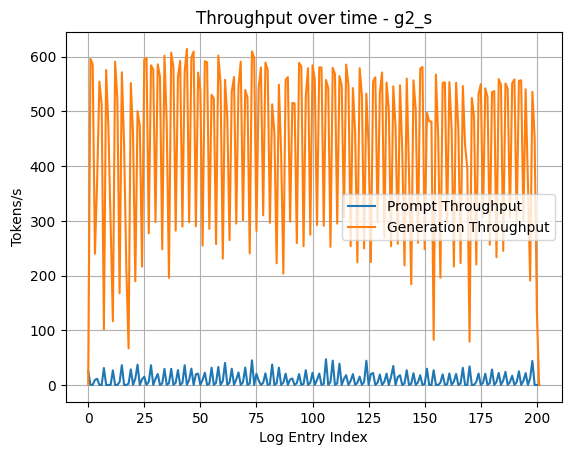

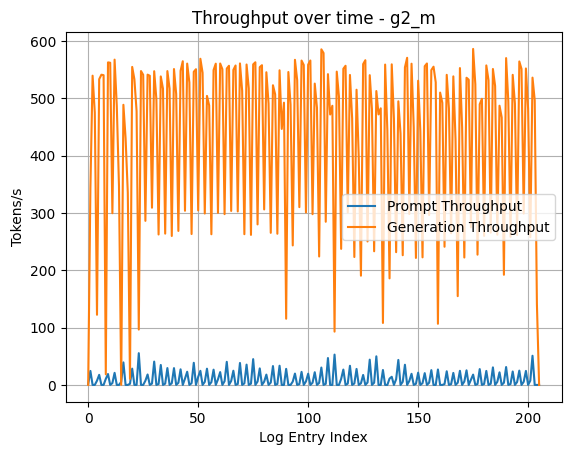

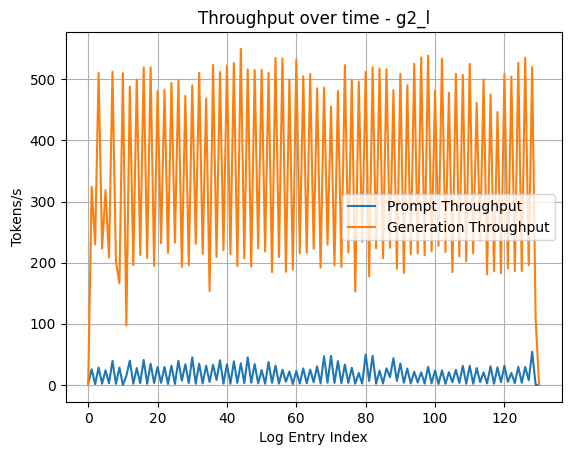

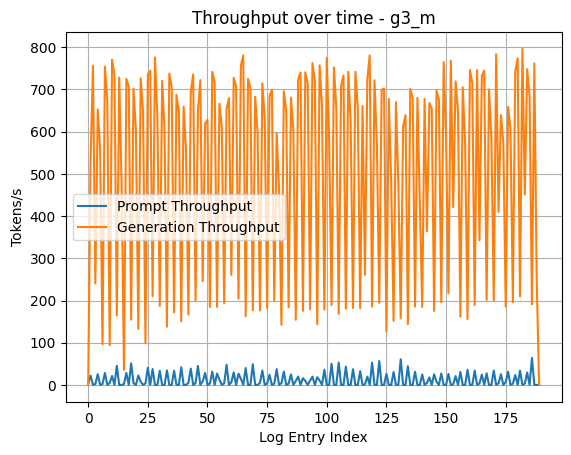

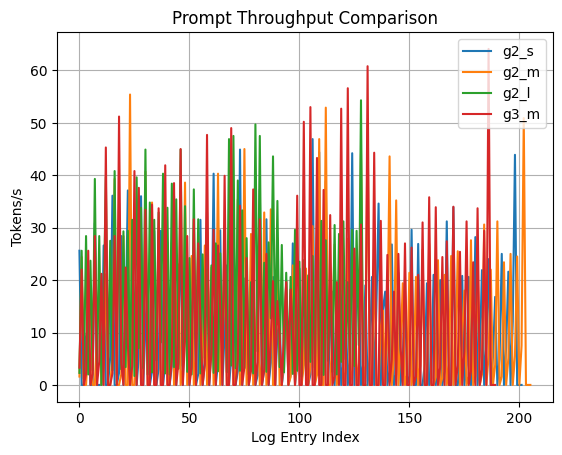

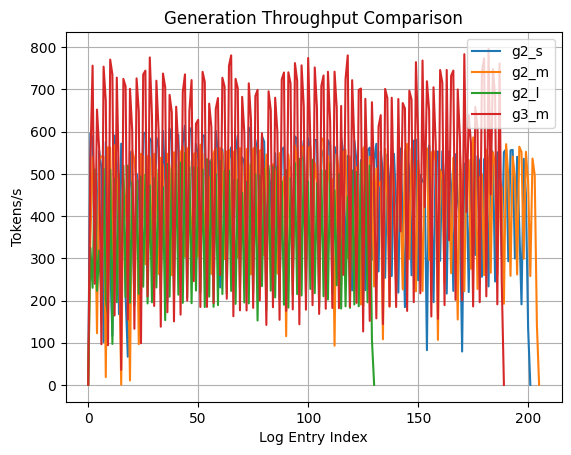

In [ ]:
import re
import matplotlib.pyplot as plt



# Store all in a dict for processing
log_data = {
    "g2": g2,
    "g2_s": g2_s,
    "g2_m": g2_m, "g2_l": g2_l,
    "g3": g3,  "g3_m": g3_m
}

pattern = re.compile(
    r"Avg prompt throughput: ([\d\.]+) tokens/s, Avg generation throughput: ([\d\.]+) tokens/s"
)

results = {}

for name, text in log_data.items():
    prompt_vals = []
    gen_vals = []

    for match in pattern.finditer(text):
        prompt_vals.append(float(match.group(1)))
        gen_vals.append(float(match.group(2)))

    if prompt_vals and gen_vals:
        results[name] = {
            "prompt_vals": prompt_vals,
            "gen_vals": gen_vals,
            "max_prompt": max(prompt_vals),
            "max_gen": max(gen_vals),
        }

# Print max values
for name, vals in results.items():
    print(f"{name}: Max Prompt Throughput = {vals['max_prompt']} tokens/s, "
          f"Max Generation Throughput = {vals['max_gen']} tokens/s")

# --- Plot individual graphs ---
for name, vals in results.items():
    plt.figure()
    plt.plot(vals["prompt_vals"], label="Prompt Throughput")
    plt.plot(vals["gen_vals"], label="Generation Throughput")
    plt.title(f"Throughput over time - {name}")
    plt.xlabel("Log Entry Index")
    plt.ylabel("Tokens/s")
    plt.legend()
    plt.grid(True)
    plt.show()

# --- Comparative plots ---
# Prompt throughput comparison
plt.figure()
for name, vals in results.items():
    plt.plot(vals["prompt_vals"], label=name)
plt.title("Prompt Throughput Comparison")
plt.xlabel("Log Entry Index")
plt.ylabel("Tokens/s")
plt.legend()
plt.grid(True)
plt.show()

# Generation throughput comparison
plt.figure()
for name, vals in results.items():
    plt.plot(vals["gen_vals"], label=name)
plt.title("Generation Throughput Comparison")
plt.xlabel("Log Entry Index")
plt.ylabel("Tokens/s")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import matplotlib.cm as cm
import numpy as np
import matplotlib.pyplot as plt

# ===== CUSTOM ORDER FOR G2/G3 ALTERNATING =====
bench_plot_order = ["2", "3", "2s", "3s", "2m", "3m", "2l", "3l"]

def get_cfg_key(run_name):
    # Extract config like "2", "3", "2s", "3m" from filename
    return run_name.split("_")[-1].replace("g", "")  # remove "g" if present

bench_sorted_runs = sorted(
    bench_data.keys(),
    key=lambda x: bench_plot_order.index(get_cfg_key(x)) if get_cfg_key(x) in bench_plot_order else 999
)

# ===== COLOR ASSIGNMENT: SAME BASE FOR G2 & G3 =====
base_configs = ["2", "2s", "2m", "2l"]  # Only for color grouping
base_color_list = cm.tab10(np.linspace(0, 1, len(base_configs)))  # Base palette
bench_color_map = {}

for run in bench_sorted_runs:
    cfg = get_cfg_key(run)  # e.g., '2', '3', '2s', '3s'
    base_cfg = cfg.replace("3", "2")  # Map g3 variants to g2 color
    if base_cfg not in base_configs:
        base_cfg = base_configs[0]  # fallback if weird name
    base_idx = base_configs.index(base_cfg)
    if cfg.startswith("2"):
        bench_color_map[run] = base_color_list[base_idx]
    else:  # g3 variant → darker shade of same base color
        bench_color_map[run] = tuple(np.array(base_color_list[base_idx]) * 0.7)

# ===== PLOT: ALL DEVICES THROUGHPUT =====
plt.figure(figsize=(10, 6))
for run in bench_sorted_runs:
    plt.plot(
        bench_data[run],
        marker='o',
        label=f"{run} (Avg: {bench_throughput[run]:.2f})",
        color=bench_color_map[run],
        linestyle="-"
    )
plt.title("Throughput Across Prompts - All Devices")
plt.xlabel("Prompt Index")
plt.ylabel("Throughput")

# Smaller legend outside the plot
plt.legend(
    fontsize=8,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.12),
    ncol=4,
    frameon=False
)

plt.tight_layout()
plt.show()


# ===== INDIVIDUAL THROUGHPUT PLOTS =====
for run in bench_sorted_runs:
    plt.figure(figsize=(8, 4))
    plt.plot(
        bench_data[run],
        marker='o',
        color=bench_color_map[run],
        linestyle="-",
        label=f"{run} (Avg: {bench_throughput[run]:.2f})"
    )
    plt.title(f"Throughput Across Prompts - {run}")
    plt.xlabel("Prompt Index")
    plt.ylabel("Throughput")
    plt.legend()
    plt.tight_layout()
    plt.show()

# ===== HISTOGRAM OF AVG THROUGHPUT =====
plt.figure(figsize=(10, 6))
bars = [bench_throughput[run] for run in bench_sorted_runs]
labels = [run for run in bench_sorted_runs]
colors = [bench_color_map[run] for run in bench_sorted_runs]

plt.bar(labels, bars, color=colors, edgecolor="black")
for i, val in enumerate(bars):
    plt.text(i, val + 0.1, f"{val:.2f}", ha="center", va="bottom", fontsize=9)
plt.title("Average Throughput per Device")
plt.xlabel("Run")
plt.ylabel("Average Throughput")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


NameError: name 'bench_data' is not defined

In [ ]:
import matplotlib.cm as cm
import numpy as np
import matplotlib.pyplot as plt

# ===== CUSTOM ORDER FOR G2/G3 ALTERNATING =====
bench_plot_order = ["2", "3", "2s", "3s", "2m", "3m", "2l", "3l"]

def get_cfg_key(run_name):
    # Extract config like "2", "3", "2s", "3m" from filename
    return run_name.split("_")[-1].replace("g", "")  # remove "g" if present

bench_sorted_runs = sorted(
    bench_data.keys(),
    key=lambda x: bench_plot_order.index(get_cfg_key(x)) if get_cfg_key(x) in bench_plot_order else 999
)

# ===== COLOR ASSIGNMENT: SAME BASE FOR G2 & G3 =====
base_configs = ["2", "2s", "2m", "2l"]  # Only for color grouping
base_color_list = cm.tab10(np.linspace(0, 1, len(base_configs)))  # Base palette
bench_color_map = {}

for run in bench_sorted_runs:
    cfg = get_cfg_key(run)  # e.g., '2', '3', '2s', '3s'
    base_cfg = cfg.replace("3", "2")  # Map g3 variants to g2 color
    if base_cfg not in base_configs:
        base_cfg = base_configs[0]  # fallback if weird name
    base_idx = base_configs.index(base_cfg)
    if cfg.startswith("2"):
        bench_color_map[run] = base_color_list[base_idx]
    else:  # g3 variant → darker shade of same base color
        bench_color_map[run] = tuple(np.array(base_color_list[base_idx]) * 0.7)

# ===== PLOT: ALL DEVICES THROUGHPUT =====
plt.figure(figsize=(10, 6))
for run in bench_sorted_runs:
    plt.plot(
        bench_data[run],  # Use bench_data[run] directly
        marker='o',
        label=f"{run} (Avg: {bench_throughput[run]:.2f})",
        color=bench_color_map[run],
        linestyle="-"
    )
plt.title("Throughput Across Prompts - All Devices")
plt.xlabel("Prompt Index")
plt.ylabel("Throughput")
plt.legend(fontsize=8, loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=4, frameon=False)
plt.tight_layout()
plt.show()

# ===== INDIVIDUAL THROUGHPUT PLOTS =====
for run in bench_sorted_runs:
    plt.figure(figsize=(8, 4))
    plt.plot(
        bench_data[run], # Use bench_data[run] directly
        marker='o',
        color=bench_color_map[run],
        linestyle="-",
        label=f"{run} (Avg: {bench_throughput[run]:.2f})"
    )
    plt.title(f"Throughput Across Prompts - {run}")
    plt.xlabel("Prompt Index")
    plt.ylabel("Throughput")
    plt.legend()
    plt.tight_layout()
    plt.show()

# ===== HISTOGRAMS FOR ALL METRICS =====
# Assuming bench_data contains only throughput for now based on the error
metrics = ["throughput"]

for metric in metrics:
    plt.figure(figsize=(10, 6))
    # Use bench_throughput which already contains the average throughput
    avg_values = [bench_throughput[run] for run in bench_sorted_runs]
    plt.bar(bench_sorted_runs, avg_values, color=[bench_color_map[run] for run in bench_sorted_runs], edgecolor="black")
    for i, val in enumerate(avg_values):
        plt.text(i, val + 0.01 * max(avg_values), f"{val:.2f}", ha="center", va="bottom", fontsize=8)
    plt.title(f"Average Throughput per Device") # Updated title
    plt.xlabel("Run")
    plt.ylabel(f"Average Throughput") # Updated ylabel
    plt.xticks(rotation=45, ha="right")

    plt.tight_layout()

    plt.show()